# State-based History-aware Artificial Reinforcement Interpretable Kernel" (Sharik)
## Open AI Gym - Atari - Breakout - Experiential Learning - Final seach for Hyper-Parameters

In [1]:
import os, sys
import pickle
import pandas as pd
import queue
import matplotlib.pyplot as plt
import random
import math
import numpy as np

In [2]:
#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=2 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s2ss10lm2sc2cs2tu0.txt -o=exp200000000_s2ss10lm2sc2cs2tu0
#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=3 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s3ss10lm2sc2cs2tu0.txt -o=exp200000000_s3ss10lm2sc2cs2tu0
#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=41 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s41ss10lm2sc2cs2tu0.txt -o=exp200000000_s41ss10lm2sc2cs2tu0

#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=0 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s0ss10lm2sc2cs2tu0.txt -o=exp200000000_s0ss10lm2sc2cs2tu0
#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=1 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s1ss10lm2sc2cs2tu0.txt -o=exp200000000_s1ss10lm2sc2cs2tu0
#python ./breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=40 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s40ss10lm2sc2cs2tu0.txt -o=exp200000000_s40ss10lm2sc2cs2tu0

#sim_test3/exp200000000_s0ss10lm2sc2cs2tu0.txt:score_avg=48.6; steps_tot=200000000; steps_avg=7072.9; lives_avg=0.6; lapse_avg="0:00:01.150267"; time="15:55:07.922909"
#sim_test3/exp200000000_s1ss10lm2sc2cs2tu0.txt:score_avg=82.7; steps_tot=200000000; steps_avg=5498.9; lives_avg=0.0; lapse_avg="0:00:00.899912"; time="16:06:22.397897"
#sim_test3/exp200000000_s2ss10lm2sc2cs2tu0.txt:score_avg=271.5; steps_tot=200000000; steps_avg=6544.3; lives_avg=0.1; lapse_avg="0:00:02.060124"; time="16:17:23.523106"
#sim_test3/exp200000000_s3ss10lm2sc2cs2tu0.txt:score_avg=54.7; steps_tot=200000000; steps_avg=5202.8; lives_avg=0.0; lapse_avg="0:00:00.709037"; time="16:37:58.079221"
#sim_test3/exp200000000_s40ss10lm2sc2cs2tu0.txt:score_avg=96.2; steps_tot=200000000; steps_avg=5822.9; lives_avg=0.0; lapse_avg="0:00:00.057923"; time="15:44:06.015451"
#sim_test3/exp200000000_s41ss10lm2sc2cs2tu0.txt:score_avg=96.3; steps_tot=200000000; steps_avg=4389.3; lives_avg=0.0; lapse_avg="0:00:00.465868"; time="16:39:02.732317"


In [3]:
exp200000000_s0ss10lm2sc2cs2tu0 = [1.0, 0, 2.0, 0, 2.0, 0, 0, 2.0, 1.0, 2.0, 0, 3.0, 0, 0, 5.0, 4.0, 0, 3.0, 2.0, 5.0, 2.0, 5.0, 2.0, 3.0, 1.0, 2.0, 0, 5.0, 2.0, 1.0, 3.0, 0, 5.0, 8.0, 3.0, 6.0, 0, 3.0, 2.0, 4.0, 3.0, 5.0, 2.0, 5.0, 2.0, 5.0, 3.0, 17.0, 6.0, 6.0, 0, 8.0, 16.0, 8.0, 6.0, 7.0, 8.0, 4.0, 7.0, 6.0, 1.0, 8.0, 8.0, 16.0, 5.0, 9.0, 9.0, 9.0, 15.0, 16.0, 14.0, 8.0, 7.0, 9.0, 15.0, 14.0, 4.0, 19.0, 16.0, 14.0, 17.0, 4.0, 10.0, 20.0, 8.0, 11.0, 11.0, 8.0, 12.0, 9.0, 20.0, 17.0, 17.0, 9.0, 11.0, 14.0, 9.0, 8.0, 10.0, 8.0, 10.0, 8.0, 17.0, 9.0, 9.0, 2.0, 9.0, 9.0, 9.0, 11.0, 9.0, 8.0, 5.0, 8.0, 10.0, 5.0, 21.0, 8.0, 4.0, 9.0, 5.0, 18.0, 7.0, 8.0, 11.0, 9.0, 20.0, 8.0, 9.0, 4.0, 9.0, 21.0, 9.0, 13.0, 12.0, 16.0, 12.0, 12.0, 26.0, 12.0, 20.0, 11.0, 21.0, 15.0, 13.0, 15.0, 10.0, 10.0, 20.0, 6.0, 2.0, 12.0, 25.0, 11.0, 14.0, 2.0, 22.0, 5.0, 11.0, 11.0, 15.0, 8.0, 11.0, 12.0, 20.0, 16.0, 4.0, 25.0, 6.0, 20.0, 7.0, 15.0, 17.0, 16.0, 17.0, 8.0, 10.0, 23.0, 20.0, 16.0, 17.0, 4.0, 22.0, 7.0, 18.0, 4.0, 18.0, 20.0, 17.0, 16.0, 16.0, 18.0, 17.0, 17.0, 13.0, 18.0, 9.0, 18.0, 19.0, 4.0, 18.0, 17.0, 8.0, 17.0, 18.0, 17.0, 15.0, 16.0, 16.0, 22.0, 17.0, 9.0, 20.0, 13.0, 22.0, 20.0, 19.0, 15.0, 14.0, 12.0, 18.0, 18.0, 18.0, 17.0, 18.0, 18.0, 3.0, 18.0, 8.0, 15.0, 17.0, 23.0, 12.0, 18.0, 18.0, 21.0, 20.0, 15.0, 18.0, 23.0, 23.0, 11.0, 20.0, 15.0, 12.0, 13.0, 11.0, 6.0, 11.0, 19.0, 13.0, 21.0, 12.0, 16.0, 30.0, 6.0, 25.0, 25.0, 20.0, 15.0, 4.0, 16.0, 15.0, 13.0, 31.0, 12.0, 26.0, 19.0, 16.0, 21.0, 13.0, 14.0, 16.0, 17.0, 13.0, 11.0, 25.0, 14.0, 5.0, 14.0, 16.0, 17.0, 21.0, 17.0, 28.0, 16.0, 20.0, 5.0, 14.0, 21.0, 17.0, 13.0, 27.0, 20.0, 15.0, 12.0, 30.0, 15.0, 23.0, 21.0, 23.0, 18.0, 25.0, 12.0, 18.0, 15.0, 22.0, 13.0, 8.0, 26.0, 4.0, 23.0, 19.0, 12.0, 28.0, 18.0, 22.0, 19.0, 24.0, 23.0, 25.0, 22.0, 19.0, 12.0, 12.0, 6.0, 22.0, 13.0, 14.0, 9.0, 12.0, 27.0, 14.0, 14.0, 12.0, 0, 20.0, 17.0, 13.0, 11.0, 12.0, 4.0, 15.0, 18.0, 23.0, 12.0, 12.0, 4.0, 11.0, 10.0, 14.0, 14.0, 13.0, 12.0, 6.0, 18.0, 9.0, 17.0, 21.0, 9.0, 19.0, 26.0, 16.0, 18.0, 18.0, 17.0, 17.0, 15.0, 15.0, 26.0, 13.0, 15.0, 10.0, 13.0, 18.0, 14.0, 16.0, 16.0, 14.0, 23.0, 18.0, 32.0, 19.0, 13.0, 15.0, 28.0, 14.0, 17.0, 26.0, 18.0, 16.0, 24.0, 17.0, 17.0, 17.0, 17.0, 15.0, 17.0, 13.0, 14.0, 17.0, 14.0, 29.0, 13.0, 16.0, 24.0, 17.0, 20.0, 26.0, 17.0, 19.0, 13.0, 25.0, 14.0, 20.0, 18.0, 20.0, 15.0, 15.0, 17.0, 17.0, 17.0, 0, 19.0, 30.0, 24.0, 27.0, 13.0, 18.0, 13.0, 21.0, 17.0, 15.0, 17.0, 22.0, 17.0, 13.0, 27.0, 13.0, 29.0, 25.0, 13.0, 19.0, 13.0, 13.0, 26.0, 17.0, 1.0, 25.0, 13.0, 19.0, 9.0, 14.0, 25.0, 14.0, 13.0, 15.0, 9.0, 8.0, 17.0, 15.0, 8.0, 8.0, 24.0, 23.0, 13.0, 29.0, 17.0, 19.0, 17.0, 25.0, 3.0, 5.0, 22.0, 21.0, 30.0, 20.0, 11.0, 17.0, 17.0, 13.0, 16.0, 14.0, 37.0, 16.0, 12.0, 14.0, 25.0, 17.0, 16.0, 16.0, 19.0, 13.0, 26.0, 27.0, 12.0, 12.0, 14.0, 26.0, 30.0, 4.0, 17.0, 18.0, 26.0, 15.0, 23.0, 18.0, 26.0, 25.0, 19.0, 23.0, 18.0, 21.0, 12.0, 27.0, 16.0, 17.0, 28.0, 18.0, 19.0, 4.0, 37.0, 17.0, 26.0, 23.0, 16.0, 30.0, 19.0, 14.0, 15.0, 16.0, 38.0, 37.0, 23.0, 18.0, 16.0, 21.0, 18.0, 23.0, 11.0, 10.0, 16.0, 26.0, 14.0, 19.0, 23.0, 14.0, 23.0, 8.0, 14.0, 27.0, 42.0, 24.0, 37.0, 23.0, 25.0, 18.0, 58.0, 17.0, 38.0, 14.0, 17.0, 14.0, 51.0, 19.0, 21.0, 17.0, 15.0, 17.0, 17.0, 18.0, 14.0, 42.0, 32.0, 17.0, 13.0, 11.0, 15.0, 24.0, 17.0, 13.0, 23.0, 22.0, 16.0, 11.0, 12.0, 24.0, 24.0, 18.0, 14.0, 16.0, 21.0, 11.0, 25.0, 14.0, 23.0, 16.0, 23.0, 20.0, 16.0, 20.0, 6.0, 14.0, 37.0, 15.0, 17.0, 27.0, 22.0, 19.0, 16.0, 12.0, 37.0, 10.0, 29.0, 15.0, 14.0, 21.0, 22.0, 20.0, 15.0, 21.0, 16.0, 8.0, 28.0, 4.0, 37.0, 11.0, 18.0, 31.0, 21.0, 24.0, 27.0, 19.0, 14.0, 15.0, 15.0, 25.0, 13.0, 18.0, 14.0, 28.0, 22.0, 16.0, 16.0, 20.0, 22.0, 18.0, 28.0, 14.0, 14.0, 24.0, 26.0, 31.0, 16.0, 28.0, 37.0, 23.0, 42.0, 23.0, 23.0, 17.0, 7.0, 14.0, 9.0, 17.0, 21.0, 38.0, 12.0, 30.0, 21.0, 15.0, 19.0, 38.0, 4.0, 16.0, 21.0, 17.0, 42.0, 17.0, 17.0, 11.0, 7.0, 16.0, 8.0, 19.0, 24.0, 20.0, 40.0, 16.0, 14.0, 4.0, 16.0, 24.0, 14.0, 26.0, 19.0, 20.0, 19.0, 38.0, 26.0, 19.0, 18.0, 38.0, 20.0, 26.0, 22.0, 23.0, 17.0, 17.0, 41.0, 37.0, 22.0, 18.0, 35.0, 25.0, 38.0, 28.0, 20.0, 17.0, 27.0, 38.0, 15.0, 15.0, 45.0, 22.0, 26.0, 21.0, 21.0, 28.0, 16.0, 23.0, 29.0, 15.0, 21.0, 25.0, 17.0, 15.0, 16.0, 23.0, 43.0, 18.0, 27.0, 20.0, 22.0, 47.0, 33.0, 19.0, 40.0, 28.0, 20.0, 19.0, 17.0, 38.0, 23.0, 2.0, 40.0, 40.0, 27.0, 18.0, 22.0, 25.0, 10.0, 29.0, 26.0, 22.0, 45.0, 48.0, 15.0, 45.0, 27.0, 15.0, 22.0, 16.0, 21.0, 20.0, 10.0, 4.0, 9.0, 18.0, 26.0, 10.0, 32.0, 45.0, 30.0, 20.0, 33.0, 4.0, 24.0, 26.0, 15.0, 18.0, 28.0, 24.0, 29.0, 15.0, 26.0, 30.0, 18.0, 12.0, 14.0, 27.0, 33.0, 14.0, 16.0, 24.0, 22.0, 28.0, 31.0, 13.0, 22.0, 19.0, 18.0, 14.0, 27.0, 19.0, 29.0, 24.0, 17.0, 29.0, 28.0, 13.0, 21.0, 44.0, 9.0, 18.0, 11.0, 33.0, 33.0, 42.0, 10.0, 24.0, 23.0, 16.0, 17.0, 21.0, 30.0, 10.0, 25.0, 22.0, 29.0, 19.0, 20.0, 26.0, 16.0, 24.0, 31.0, 16.0, 25.0, 30.0, 24.0, 26.0, 16.0, 10.0, 24.0, 29.0, 22.0, 35.0, 19.0, 46.0, 9.0, 22.0, 11.0, 31.0, 17.0, 24.0, 21.0, 20.0, 19.0, 36.0, 14.0, 50.0, 16.0, 23.0, 35.0, 27.0, 50.0, 46.0, 15.0, 25.0, 21.0, 43.0, 16.0, 40.0, 24.0, 25.0, 29.0, 11.0, 17.0, 12.0, 6.0, 24.0, 11.0, 35.0, 43.0, 43.0, 23.0, 27.0, 33.0, 13.0, 27.0, 22.0, 23.0, 28.0, 26.0, 36.0, 32.0, 26.0, 23.0, 23.0, 38.0, 20.0, 30.0, 22.0, 8.0, 20.0, 20.0, 13.0, 20.0, 23.0, 22.0, 25.0, 28.0, 51.0, 26.0, 15.0, 29.0, 21.0, 32.0, 11.0, 15.0, 37.0, 23.0, 22.0, 12.0, 43.0, 22.0, 43.0, 30.0, 17.0, 18.0, 28.0, 4.0, 24.0, 35.0, 29.0, 33.0, 31.0, 16.0, 11.0, 27.0, 21.0, 33.0, 32.0, 23.0, 43.0, 30.0, 16.0, 22.0, 23.0, 31.0, 22.0, 37.0, 28.0, 20.0, 41.0, 31.0, 32.0, 45.0, 24.0, 24.0, 11.0, 25.0, 39.0, 29.0, 22.0, 27.0, 13.0, 25.0, 12.0, 16.0, 21.0, 4.0, 21.0, 28.0, 13.0, 12.0, 43.0, 27.0, 45.0, 48.0, 30.0, 35.0, 19.0, 22.0, 36.0, 24.0, 32.0, 13.0, 31.0, 29.0, 25.0, 16.0, 25.0, 27.0, 3.0, 16.0, 7.0, 20.0, 23.0, 20.0, 33.0, 17.0, 17.0, 25.0, 16.0, 31.0, 33.0, 32.0, 16.0, 19.0, 15.0, 19.0, 49.0, 26.0, 29.0, 28.0, 31.0, 15.0, 26.0, 46.0, 30.0, 27.0, 22.0, 30.0, 12.0, 24.0, 33.0, 27.0, 29.0, 33.0, 21.0, 25.0, 15.0, 24.0, 4.0, 11.0, 14.0, 30.0, 16.0, 9.0, 19.0, 21.0, 22.0, 49.0, 40.0, 43.0, 17.0, 20.0, 17.0, 37.0, 31.0, 6.0, 45.0, 25.0, 41.0, 23.0, 47.0, 28.0, 43.0, 20.0, 49.0, 26.0, 38.0, 24.0, 27.0, 31.0, 1.0, 32.0, 12.0, 31.0, 23.0, 30.0, 16.0, 35.0, 53.0, 26.0, 24.0, 16.0, 27.0, 30.0, 53.0, 29.0, 35.0, 30.0, 29.0, 30.0, 21.0, 52.0, 28.0, 34.0, 23.0, 22.0, 13.0, 30.0, 28.0, 39.0, 37.0, 23.0, 49.0, 25.0, 11.0, 23.0, 23.0, 29.0, 21.0, 23.0, 26.0, 24.0, 34.0, 16.0, 27.0, 16.0, 32.0, 29.0, 31.0, 24.0, 22.0, 50.0, 29.0, 27.0, 29.0, 32.0, 29.0, 60.0, 25.0, 29.0, 24.0, 26.0, 25.0, 28.0, 27.0, 43.0, 32.0, 23.0, 29.0, 21.0, 19.0, 13.0, 40.0, 28.0, 21.0, 43.0, 43.0, 15.0, 43.0, 34.0, 34.0, 30.0, 22.0, 24.0, 25.0, 32.0, 24.0, 38.0, 7.0, 28.0, 31.0, 51.0, 38.0, 24.0, 23.0, 29.0, 48.0, 22.0, 25.0, 32.0, 26.0, 31.0, 25.0, 30.0, 39.0, 24.0, 55.0, 30.0, 16.0, 20.0, 36.0, 38.0, 35.0, 30.0, 28.0, 31.0, 28.0, 31.0, 34.0, 23.0, 30.0, 59.0, 24.0, 41.0, 33.0, 33.0, 26.0, 36.0, 28.0, 30.0, 33.0, 33.0, 24.0, 30.0, 27.0, 36.0, 57.0, 32.0, 27.0, 38.0, 33.0, 27.0, 30.0, 38.0, 32.0, 27.0, 34.0, 28.0, 28.0, 31.0, 43.0, 36.0, 9.0, 31.0, 32.0, 35.0, 11.0, 35.0, 30.0, 26.0, 36.0, 33.0, 30.0, 62.0, 30.0, 12.0, 30.0, 35.0, 54.0, 26.0, 43.0, 30.0, 30.0, 22.0, 40.0, 30.0, 35.0, 30.0, 35.0, 42.0, 30.0, 35.0, 34.0, 32.0, 43.0, 51.0, 38.0, 10.0, 41.0, 32.0, 53.0, 30.0, 36.0, 36.0, 47.0, 23.0, 36.0, 7.0, 35.0, 27.0, 7.0, 23.0, 34.0, 43.0, 26.0, 26.0, 34.0, 43.0, 35.0, 11.0, 47.0, 10.0, 29.0, 12.0, 42.0, 30.0, 19.0, 28.0, 35.0, 23.0, 14.0, 30.0, 43.0, 38.0, 39.0, 38.0, 38.0, 41.0, 39.0, 40.0, 32.0, 36.0, 31.0, 42.0, 25.0, 26.0, 8.0, 35.0, 29.0, 15.0, 43.0, 24.0, 20.0, 21.0, 24.0, 53.0, 9.0, 12.0, 40.0, 56.0, 38.0, 32.0, 31.0, 38.0, 55.0, 38.0, 21.0, 20.0, 33.0, 38.0, 38.0, 26.0, 22.0, 60.0, 20.0, 10.0, 35.0, 15.0, 30.0, 16.0, 28.0, 21.0, 25.0, 66.0, 33.0, 23.0, 31.0, 26.0, 32.0, 11.0, 13.0, 21.0, 43.0, 28.0, 4.0, 34.0, 22.0, 34.0, 8.0, 16.0, 61.0, 30.0, 26.0, 67.0, 32.0, 4.0, 7.0, 47.0, 23.0, 10.0, 28.0, 38.0, 20.0, 61.0, 29.0, 24.0, 26.0, 34.0, 59.0, 32.0, 65.0, 30.0, 6.0, 23.0, 29.0, 26.0, 60.0, 27.0, 24.0, 43.0, 36.0, 33.0, 26.0, 27.0, 32.0, 23.0, 31.0, 27.0, 16.0, 26.0, 28.0, 25.0, 17.0, 35.0, 36.0, 15.0, 29.0, 30.0, 28.0, 43.0, 5.0, 43.0, 30.0, 10.0, 38.0, 26.0, 26.0, 13.0, 29.0, 35.0, 14.0, 34.0, 30.0, 36.0, 34.0, 43.0, 25.0, 16.0, 30.0, 32.0, 4.0, 34.0, 4.0, 32.0, 32.0, 4.0, 29.0, 29.0, 33.0, 13.0, 33.0, 43.0, 9.0, 33.0, 43.0, 44.0, 29.0, 33.0, 33.0, 30.0, 30.0, 7.0, 36.0, 34.0, 20.0, 30.0, 43.0, 21.0, 34.0, 25.0, 22.0, 30.0, 32.0, 22.0, 4.0, 43.0, 43.0, 30.0, 25.0, 26.0, 36.0, 36.0, 19.0, 31.0, 35.0, 32.0, 30.0, 15.0, 22.0, 19.0, 38.0, 36.0, 24.0, 62.0, 38.0, 25.0, 4.0, 69.0, 44.0, 35.0, 12.0, 23.0, 23.0, 35.0, 28.0, 22.0, 22.0, 32.0, 28.0, 22.0, 30.0, 30.0, 22.0, 22.0, 35.0, 42.0, 7.0, 23.0, 57.0, 46.0, 62.0, 27.0, 31.0, 30.0, 10.0, 22.0, 22.0, 31.0, 30.0, 32.0, 24.0, 34.0, 22.0, 35.0, 32.0, 4.0, 60.0, 48.0, 25.0, 30.0, 23.0, 7.0, 22.0, 37.0, 31.0, 33.0, 38.0, 28.0, 32.0, 26.0, 20.0, 48.0, 23.0, 5.0, 21.0, 4.0, 38.0, 26.0, 32.0, 29.0, 22.0, 48.0, 43.0, 21.0, 30.0, 30.0, 22.0, 31.0, 24.0, 68.0, 24.0, 24.0, 36.0, 10.0, 30.0, 28.0, 22.0, 34.0, 36.0, 33.0, 36.0, 16.0, 68.0, 35.0, 26.0, 9.0, 62.0, 24.0, 30.0, 4.0, 9.0, 33.0, 6.0, 32.0, 43.0, 36.0, 42.0, 28.0, 28.0, 48.0, 17.0, 4.0, 25.0, 35.0, 4.0, 23.0, 24.0, 26.0, 28.0, 25.0, 27.0, 34.0, 48.0, 46.0, 14.0, 35.0, 68.0, 21.0, 62.0, 22.0, 30.0, 28.0, 12.0, 18.0, 14.0, 22.0, 73.0, 28.0, 32.0, 44.0, 28.0, 35.0, 36.0, 26.0, 22.0, 29.0, 38.0, 43.0, 68.0, 14.0, 74.0, 6.0, 21.0, 36.0, 19.0, 17.0, 35.0, 22.0, 69.0, 28.0, 44.0, 24.0, 15.0, 35.0, 44.0, 41.0, 66.0, 7.0, 7.0, 4.0, 28.0, 27.0, 4.0, 4.0, 35.0, 25.0, 28.0, 32.0, 16.0, 4.0, 28.0, 35.0, 4.0, 22.0, 22.0, 31.0, 13.0, 35.0, 24.0, 4.0, 4.0, 52.0, 23.0, 30.0, 12.0, 38.0, 22.0, 22.0, 4.0, 19.0, 51.0, 49.0, 30.0, 4.0, 35.0, 30.0, 4.0, 16.0, 15.0, 25.0, 32.0, 49.0, 35.0, 22.0, 26.0, 28.0, 25.0, 4.0, 31.0, 32.0, 49.0, 15.0, 18.0, 16.0, 4.0, 15.0, 26.0, 28.0, 38.0, 32.0, 15.0, 36.0, 4.0, 74.0, 24.0, 82.0, 11.0, 37.0, 30.0, 24.0, 11.0, 4.0, 29.0, 4.0, 22.0, 81.0, 35.0, 21.0, 35.0, 34.0, 35.0, 32.0, 26.0, 25.0, 37.0, 15.0, 28.0, 23.0, 5.0, 23.0, 33.0, 24.0, 4.0, 28.0, 28.0, 24.0, 28.0, 34.0, 32.0, 18.0, 24.0, 22.0, 42.0, 22.0, 4.0, 36.0, 24.0, 4.0, 15.0, 17.0, 30.0, 34.0, 26.0, 6.0, 23.0, 24.0, 26.0, 4.0, 40.0, 4.0, 30.0, 20.0, 6.0, 23.0, 24.0, 4.0, 36.0, 15.0, 4.0, 36.0, 49.0, 16.0, 28.0, 36.0, 24.0, 31.0, 29.0, 43.0, 28.0, 33.0, 5.0, 24.0, 22.0, 31.0, 22.0, 17.0, 38.0, 49.0, 42.0, 49.0, 10.0, 30.0, 49.0, 45.0, 27.0, 32.0, 26.0, 34.0, 24.0, 22.0, 13.0, 24.0, 49.0, 82.0, 31.0, 22.0, 31.0, 15.0, 32.0, 28.0, 80.0, 16.0, 28.0, 26.0, 40.0, 28.0, 36.0, 4.0, 32.0, 36.0, 30.0, 4.0, 23.0, 30.0, 244.0, 25.0, 30.0, 30.0, 27.0, 26.0, 20.0, 30.0, 35.0, 39.0, 19.0, 30.0, 18.0, 14.0, 30.0, 27.0, 29.0, 26.0, 22.0, 35.0, 21.0, 22.0, 31.0, 26.0, 96.0, 15.0, 28.0, 30.0, 14.0, 78.0, 23.0, 36.0, 27.0, 49.0, 28.0, 28.0, 29.0, 22.0, 13.0, 28.0, 26.0, 25.0, 28.0, 35.0, 14.0, 22.0, 27.0, 29.0, 16.0, 32.0, 29.0, 23.0, 20.0, 53.0, 31.0, 49.0, 30.0, 18.0, 23.0, 30.0, 26.0, 35.0, 40.0, 12.0, 29.0, 19.0, 50.0, 16.0, 36.0, 30.0, 49.0, 33.0, 37.0, 80.0, 28.0, 37.0, 39.0, 46.0, 66.0, 34.0, 17.0, 33.0, 25.0, 92.0, 23.0, 243.0, 24.0, 40.0, 34.0, 73.0, 23.0, 23.0, 40.0, 43.0, 70.0, 38.0, 22.0, 82.0, 46.0, 68.0, 15.0, 22.0, 24.0, 32.0, 66.0, 33.0, 22.0, 4.0, 40.0, 26.0, 63.0, 35.0, 24.0, 27.0, 13.0, 37.0, 16.0, 243.0, 38.0, 43.0, 32.0, 22.0, 75.0, 39.0, 49.0, 30.0, 11.0, 43.0, 20.0, 62.0, 32.0, 43.0, 4.0, 40.0, 49.0, 49.0, 34.0, 37.0, 37.0, 22.0, 73.0, 68.0, 31.0, 55.0, 40.0, 39.0, 29.0, 84.0, 36.0, 37.0, 14.0, 35.0, 20.0, 51.0, 29.0, 32.0, 77.0, 41.0, 38.0, 24.0, 29.0, 28.0, 43.0, 37.0, 51.0, 48.0, 11.0, 39.0, 37.0, 37.0, 49.0, 38.0, 25.0, 78.0, 51.0, 26.0, 79.0, 49.0, 46.0, 85.0, 23.0, 44.0, 32.0, 31.0, 4.0, 29.0, 36.0, 28.0, 28.0, 37.0, 30.0, 26.0, 22.0, 37.0, 50.0, 36.0, 86.0, 13.0, 36.0, 17.0, 29.0, 36.0, 16.0, 4.0, 4.0, 4.0, 16.0, 23.0, 44.0, 81.0, 4.0, 241.0, 4.0, 71.0, 28.0, 30.0, 82.0, 44.0, 32.0, 29.0, 28.0, 34.0, 4.0, 57.0, 36.0, 34.0, 29.0, 38.0, 49.0, 46.0, 24.0, 43.0, 37.0, 37.0, 40.0, 22.0, 50.0, 43.0, 78.0, 10.0, 15.0, 37.0, 92.0, 89.0, 32.0, 23.0, 28.0, 82.0, 88.0, 49.0, 39.0, 24.0, 22.0, 8.0, 15.0, 32.0, 28.0, 19.0, 10.0, 35.0, 15.0, 48.0, 15.0, 74.0, 60.0, 50.0, 23.0, 18.0, 22.0, 4.0, 35.0, 32.0, 46.0, 38.0, 68.0, 81.0, 49.0, 86.0, 38.0, 53.0, 51.0, 0, 24.0, 13.0, 39.0, 40.0, 16.0, 44.0, 20.0, 34.0, 10.0, 56.0, 40.0, 36.0, 32.0, 44.0, 34.0, 57.0, 53.0, 34.0, 14.0, 49.0, 37.0, 24.0, 16.0, 22.0, 37.0, 33.0, 88.0, 25.0, 32.0, 20.0, 37.0, 39.0, 32.0, 17.0, 43.0, 27.0, 22.0, 16.0, 58.0, 44.0, 44.0, 49.0, 46.0, 252.0, 48.0, 36.0, 62.0, 45.0, 33.0, 46.0, 16.0, 49.0, 34.0, 39.0, 34.0, 49.0, 46.0, 4.0, 4.0, 15.0, 51.0, 12.0, 20.0, 84.0, 81.0, 34.0, 10.0, 31.0, 43.0, 35.0, 46.0, 26.0, 37.0, 84.0, 11.0, 39.0, 8.0, 43.0, 36.0, 22.0, 51.0, 37.0, 38.0, 32.0, 15.0, 46.0, 38.0, 33.0, 37.0, 15.0, 41.0, 34.0, 36.0, 29.0, 68.0, 55.0, 22.0, 85.0, 35.0, 14.0, 29.0, 42.0, 40.0, 10.0, 28.0, 30.0, 34.0, 15.0, 24.0, 40.0, 49.0, 10.0, 40.0, 45.0, 23.0, 15.0, 47.0, 26.0, 16.0, 51.0, 39.0, 85.0, 34.0, 40.0, 16.0, 6.0, 31.0, 35.0, 65.0, 29.0, 11.0, 49.0, 39.0, 13.0, 40.0, 10.0, 36.0, 4.0, 49.0, 60.0, 27.0, 42.0, 40.0, 58.0, 43.0, 34.0, 49.0, 49.0, 49.0, 37.0, 42.0, 4.0, 45.0, 4.0, 46.0, 4.0, 7.0, 47.0, 28.0, 34.0, 44.0, 40.0, 42.0, 37.0, 41.0, 26.0, 21.0, 4.0, 43.0, 28.0, 43.0, 256.0, 39.0, 35.0, 49.0, 30.0, 32.0, 25.0, 38.0, 40.0, 86.0, 45.0, 28.0, 20.0, 35.0, 37.0, 33.0, 22.0, 97.0, 15.0, 17.0, 17.0, 22.0, 14.0, 36.0, 26.0, 37.0, 22.0, 14.0, 49.0, 39.0, 40.0, 43.0, 40.0, 43.0, 43.0, 42.0, 48.0, 37.0, 28.0, 30.0, 28.0, 17.0, 31.0, 32.0, 45.0, 4.0, 49.0, 22.0, 51.0, 84.0, 21.0, 37.0, 34.0, 27.0, 33.0, 4.0, 44.0, 51.0, 37.0, 26.0, 35.0, 28.0, 40.0, 49.0, 23.0, 47.0, 92.0, 36.0, 22.0, 51.0, 87.0, 38.0, 4.0, 41.0, 34.0, 45.0, 57.0, 85.0, 36.0, 46.0, 21.0, 30.0, 22.0, 42.0, 35.0, 43.0, 39.0, 28.0, 14.0, 17.0, 36.0, 39.0, 55.0, 31.0, 31.0, 37.0, 36.0, 43.0, 26.0, 6.0, 224.0, 25.0, 10.0, 229.0, 37.0, 34.0, 32.0, 37.0, 5.0, 25.0, 4.0, 30.0, 4.0, 4.0, 4.0, 36.0, 47.0, 46.0, 34.0, 54.0, 52.0, 52.0, 4.0, 22.0, 27.0, 36.0, 59.0, 24.0, 54.0, 42.0, 32.0, 51.0, 31.0, 53.0, 44.0, 30.0, 43.0, 18.0, 4.0, 41.0, 56.0, 16.0, 31.0, 61.0, 36.0, 56.0, 53.0, 36.0, 49.0, 56.0, 22.0, 30.0, 4.0, 34.0, 140.0, 46.0, 56.0, 39.0, 50.0, 47.0, 27.0, 27.0, 34.0, 34.0, 4.0, 13.0, 41.0, 36.0, 27.0, 35.0, 34.0, 38.0, 36.0, 39.0, 22.0, 54.0, 64.0, 28.0, 16.0, 32.0, 62.0, 46.0, 41.0, 41.0, 20.0, 23.0, 32.0, 36.0, 4.0, 15.0, 26.0, 16.0, 9.0, 41.0, 16.0, 36.0, 54.0, 65.0, 34.0, 46.0, 57.0, 59.0, 36.0, 30.0, 41.0, 25.0, 36.0, 65.0, 34.0, 33.0, 47.0, 51.0, 61.0, 46.0, 45.0, 15.0, 23.0, 30.0, 24.0, 46.0, 44.0, 11.0, 69.0, 51.0, 38.0, 75.0, 30.0, 24.0, 28.0, 58.0, 53.0, 16.0, 52.0, 32.0, 38.0, 20.0, 46.0, 31.0, 28.0, 38.0, 52.0, 55.0, 38.0, 10.0, 51.0, 73.0, 34.0, 37.0, 28.0, 74.0, 47.0, 56.0, 17.0, 60.0, 36.0, 32.0, 232.0, 39.0, 54.0, 38.0, 48.0, 13.0, 45.0, 72.0, 11.0, 65.0, 32.0, 40.0, 23.0, 27.0, 50.0, 46.0, 64.0, 52.0, 10.0, 36.0, 30.0, 57.0, 36.0, 22.0, 16.0, 28.0, 36.0, 10.0, 44.0, 46.0, 50.0, 13.0, 47.0, 52.0, 26.0, 26.0, 15.0, 10.0, 40.0, 65.0, 36.0, 32.0, 18.0, 22.0, 40.0, 57.0, 39.0, 30.0, 36.0, 49.0, 10.0, 27.0, 58.0, 4.0, 36.0, 56.0, 4.0, 24.0, 45.0, 35.0, 62.0, 57.0, 32.0, 15.0, 39.0, 46.0, 45.0, 4.0, 44.0, 50.0, 49.0, 46.0, 35.0, 36.0, 49.0, 23.0, 23.0, 49.0, 29.0, 43.0, 40.0, 30.0, 37.0, 25.0, 78.0, 38.0, 40.0, 37.0, 55.0, 4.0, 49.0, 4.0, 243.0, 3.0, 34.0, 34.0, 54.0, 50.0, 31.0, 32.0, 53.0, 50.0, 22.0, 32.0, 10.0, 57.0, 16.0, 11.0, 10.0, 30.0, 53.0, 44.0, 44.0, 56.0, 41.0, 4.0, 86.0, 26.0, 52.0, 52.0, 11.0, 49.0, 4.0, 24.0, 34.0, 26.0, 41.0, 26.0, 49.0, 16.0, 32.0, 27.0, 29.0, 17.0, 44.0, 50.0, 34.0, 52.0, 4.0, 34.0, 44.0, 53.0, 34.0, 46.0, 57.0, 6.0, 36.0, 49.0, 36.0, 45.0, 49.0, 73.0, 38.0, 49.0, 70.0, 53.0, 69.0, 44.0, 40.0, 35.0, 53.0, 52.0, 31.0, 44.0, 59.0, 12.0, 74.0, 38.0, 18.0, 32.0, 24.0, 27.0, 59.0, 15.0, 55.0, 22.0, 17.0, 41.0, 13.0, 38.0, 28.0, 16.0, 30.0, 34.0, 32.0, 32.0, 18.0, 17.0, 34.0, 59.0, 37.0, 43.0, 60.0, 24.0, 38.0, 40.0, 36.0, 26.0, 54.0, 53.0, 57.0, 65.0, 49.0, 29.0, 30.0, 15.0, 54.0, 15.0, 66.0, 32.0, 22.0, 35.0, 61.0, 4.0, 23.0, 44.0, 32.0, 76.0, 27.0, 35.0, 46.0, 28.0, 25.0, 32.0, 4.0, 40.0, 4.0, 50.0, 66.0, 36.0, 26.0, 25.0, 32.0, 34.0, 35.0, 15.0, 49.0, 54.0, 46.0, 76.0, 45.0, 23.0, 49.0, 49.0, 11.0, 36.0, 36.0, 34.0, 53.0, 34.0, 40.0, 24.0, 53.0, 16.0, 55.0, 12.0, 28.0, 35.0, 47.0, 74.0, 34.0, 24.0, 4.0, 38.0, 29.0, 53.0, 50.0, 11.0, 35.0, 53.0, 33.0, 51.0, 36.0, 34.0, 51.0, 53.0, 27.0, 15.0, 22.0, 57.0, 16.0, 41.0, 36.0, 46.0, 20.0, 44.0, 34.0, 31.0, 46.0, 42.0, 50.0, 32.0, 36.0, 47.0, 45.0, 43.0, 46.0, 36.0, 18.0, 40.0, 17.0, 55.0, 54.0, 41.0, 22.0, 57.0, 55.0, 51.0, 57.0, 41.0, 30.0, 51.0, 54.0, 45.0, 38.0, 56.0, 51.0, 30.0, 239.0, 18.0, 17.0, 30.0, 26.0, 24.0, 56.0, 52.0, 16.0, 28.0, 42.0, 41.0, 57.0, 49.0, 36.0, 36.0, 43.0, 49.0, 257.0, 36.0, 28.0, 51.0, 16.0, 48.0, 24.0, 65.0, 38.0, 84.0, 26.0, 30.0, 51.0, 36.0, 36.0, 49.0, 36.0, 36.0, 47.0, 13.0, 64.0, 17.0, 52.0, 45.0, 20.0, 34.0, 52.0, 26.0, 52.0, 4.0, 19.0, 36.0, 46.0, 4.0, 27.0, 18.0, 46.0, 5.0, 46.0, 4.0, 37.0, 27.0, 30.0, 37.0, 6.0, 50.0, 33.0, 49.0, 58.0, 53.0, 31.0, 46.0, 27.0, 43.0, 4.0, 26.0, 54.0, 26.0, 261.0, 30.0, 50.0, 22.0, 54.0, 53.0, 37.0, 4.0, 36.0, 64.0, 32.0, 54.0, 65.0, 49.0, 49.0, 40.0, 60.0, 48.0, 26.0, 74.0, 4.0, 30.0, 38.0, 11.0, 22.0, 22.0, 38.0, 48.0, 40.0, 31.0, 23.0, 4.0, 40.0, 30.0, 50.0, 6.0, 53.0, 51.0, 49.0, 25.0, 40.0, 33.0, 61.0, 49.0, 38.0, 26.0, 86.0, 36.0, 44.0, 36.0, 23.0, 63.0, 91.0, 11.0, 59.0, 57.0, 63.0, 16.0, 53.0, 64.0, 92.0, 91.0, 32.0, 27.0, 8.0, 36.0, 56.0, 38.0, 86.0, 44.0, 74.0, 38.0, 34.0, 41.0, 40.0, 58.0, 49.0, 4.0, 38.0, 4.0, 39.0, 16.0, 28.0, 53.0, 27.0, 39.0, 37.0, 9.0, 10.0, 49.0, 28.0, 44.0, 15.0, 60.0, 50.0, 33.0, 42.0, 4.0, 57.0, 33.0, 45.0, 49.0, 59.0, 4.0, 30.0, 23.0, 20.0, 44.0, 17.0, 12.0, 13.0, 40.0, 22.0, 17.0, 4.0, 6.0, 26.0, 28.0, 44.0, 20.0, 28.0, 59.0, 26.0, 53.0, 47.0, 66.0, 51.0, 23.0, 50.0, 40.0, 11.0, 49.0, 28.0, 38.0, 30.0, 41.0, 30.0, 22.0, 17.0, 15.0, 37.0, 52.0, 17.0, 59.0, 21.0, 40.0, 48.0, 49.0, 36.0, 17.0, 86.0, 24.0, 41.0, 34.0, 41.0, 54.0, 49.0, 23.0, 55.0, 69.0, 53.0, 49.0, 52.0, 52.0, 4.0, 29.0, 36.0, 36.0, 97.0, 30.0, 29.0, 23.0, 47.0, 23.0, 13.0, 42.0, 29.0, 41.0, 58.0, 40.0, 24.0, 44.0, 49.0, 22.0, 11.0, 10.0, 55.0, 53.0, 56.0, 29.0, 50.0, 50.0, 49.0, 49.0, 44.0, 44.0, 60.0, 44.0, 38.0, 49.0, 51.0, 40.0, 50.0, 88.0, 44.0, 49.0, 27.0, 34.0, 32.0, 55.0, 36.0, 11.0, 6.0, 46.0, 51.0, 27.0, 55.0, 49.0, 41.0, 17.0, 21.0, 38.0, 66.0, 28.0, 41.0, 50.0, 28.0, 6.0, 23.0, 4.0, 4.0, 53.0, 27.0, 42.0, 32.0, 41.0, 61.0, 36.0, 27.0, 4.0, 24.0, 27.0, 46.0, 66.0, 16.0, 33.0, 12.0, 55.0, 33.0, 92.0, 54.0, 30.0, 42.0, 7.0, 29.0, 54.0, 52.0, 59.0, 46.0, 58.0, 17.0, 17.0, 21.0, 22.0, 63.0, 32.0, 22.0, 39.0, 50.0, 22.0, 46.0, 55.0, 50.0, 22.0, 32.0, 37.0, 60.0, 36.0, 8.0, 22.0, 36.0, 36.0, 32.0, 4.0, 34.0, 11.0, 34.0, 35.0, 82.0, 44.0, 66.0, 35.0, 63.0, 4.0, 84.0, 26.0, 44.0, 61.0, 31.0, 28.0, 51.0, 4.0, 45.0, 64.0, 12.0, 27.0, 28.0, 11.0, 22.0, 57.0, 35.0, 27.0, 51.0, 36.0, 43.0, 41.0, 46.0, 42.0, 52.0, 54.0, 27.0, 57.0, 10.0, 55.0, 4.0, 42.0, 42.0, 66.0, 4.0, 50.0, 36.0, 46.0, 41.0, 50.0, 51.0, 54.0, 17.0, 49.0, 54.0, 4.0, 28.0, 22.0, 28.0, 63.0, 41.0, 17.0, 36.0, 53.0, 63.0, 22.0, 44.0, 46.0, 68.0, 17.0, 33.0, 28.0, 27.0, 51.0, 61.0, 36.0, 46.0, 4.0, 10.0, 44.0, 29.0, 45.0, 36.0, 4.0, 27.0, 30.0, 88.0, 22.0, 54.0, 51.0, 59.0, 20.0, 22.0, 23.0, 35.0, 44.0, 34.0, 35.0, 30.0, 33.0, 4.0, 56.0, 4.0, 72.0, 87.0, 60.0, 22.0, 53.0, 4.0, 51.0, 70.0, 18.0, 37.0, 61.0, 22.0, 51.0, 49.0, 37.0, 23.0, 4.0, 45.0, 17.0, 38.0, 66.0, 63.0, 47.0, 22.0, 36.0, 48.0, 38.0, 61.0, 32.0, 51.0, 38.0, 37.0, 29.0, 69.0, 51.0, 41.0, 24.0, 4.0, 47.0, 49.0, 36.0, 36.0, 7.0, 27.0, 58.0, 13.0, 41.0, 66.0, 63.0, 53.0, 36.0, 42.0, 32.0, 70.0, 61.0, 27.0, 4.0, 21.0, 33.0, 22.0, 4.0, 4.0, 21.0, 51.0, 30.0, 57.0, 51.0, 57.0, 22.0, 70.0, 49.0, 46.0, 24.0, 38.0, 27.0, 84.0, 70.0, 49.0, 37.0, 44.0, 250.0, 20.0, 36.0, 36.0, 33.0, 39.0, 46.0, 51.0, 46.0, 23.0, 8.0, 36.0, 64.0, 24.0, 70.0, 22.0, 31.0, 50.0, 4.0, 19.0, 36.0, 15.0, 18.0, 27.0, 50.0, 22.0, 80.0, 42.0, 51.0, 30.0, 31.0, 17.0, 252.0, 63.0, 14.0, 38.0, 29.0, 49.0, 40.0, 61.0, 4.0, 4.0, 63.0, 46.0, 4.0, 44.0, 37.0, 19.0, 38.0, 57.0, 47.0, 34.0, 38.0, 49.0, 51.0, 53.0, 57.0, 29.0, 30.0, 37.0, 50.0, 37.0, 4.0, 44.0, 30.0, 4.0, 27.0, 42.0, 45.0, 40.0, 41.0, 30.0, 66.0, 263.0, 22.0, 63.0, 51.0, 51.0, 255.0, 36.0, 4.0, 33.0, 27.0, 19.0, 40.0, 46.0, 42.0, 41.0, 28.0, 36.0, 23.0, 4.0, 25.0, 11.0, 36.0, 41.0, 56.0, 44.0, 39.0, 30.0, 66.0, 15.0, 42.0, 29.0, 32.0, 26.0, 4.0, 36.0, 51.0, 57.0, 59.0, 27.0, 46.0, 41.0, 51.0, 17.0, 24.0, 51.0, 30.0, 51.0, 53.0, 68.0, 41.0, 36.0, 41.0, 4.0, 50.0, 4.0, 4.0, 33.0, 42.0, 36.0, 32.0, 44.0, 28.0, 27.0, 25.0, 17.0, 22.0, 43.0, 23.0, 53.0, 51.0, 44.0, 36.0, 16.0, 4.0, 55.0, 26.0, 30.0, 18.0, 15.0, 70.0, 249.0, 26.0, 52.0, 36.0, 4.0, 4.0, 4.0, 11.0, 32.0, 51.0, 23.0, 44.0, 22.0, 22.0, 4.0, 15.0, 61.0, 13.0, 55.0, 17.0, 4.0, 51.0, 55.0, 255.0, 38.0, 22.0, 30.0, 4.0, 53.0, 22.0, 32.0, 63.0, 19.0, 55.0, 36.0, 59.0, 27.0, 102.0, 53.0, 4.0, 19.0, 81.0, 31.0, 22.0, 26.0, 37.0, 31.0, 39.0, 36.0, 30.0, 48.0, 51.0, 38.0, 4.0, 30.0, 75.0, 13.0, 63.0, 40.0, 4.0, 36.0, 60.0, 11.0, 27.0, 58.0, 22.0, 41.0, 30.0, 29.0, 51.0, 22.0, 53.0, 65.0, 20.0, 54.0, 31.0, 37.0, 56.0, 42.0, 4.0, 52.0, 24.0, 49.0, 22.0, 22.0, 63.0, 28.0, 49.0, 51.0, 4.0, 34.0, 50.0, 51.0, 36.0, 44.0, 26.0, 50.0, 65.0, 4.0, 49.0, 64.0, 38.0, 4.0, 16.0, 30.0, 46.0, 28.0, 51.0, 7.0, 53.0, 54.0, 47.0, 51.0, 30.0, 43.0, 27.0, 6.0, 54.0, 68.0, 50.0, 44.0, 58.0, 49.0, 37.0, 55.0, 56.0, 36.0, 33.0, 28.0, 4.0, 28.0, 14.0, 41.0, 6.0, 46.0, 56.0, 55.0, 43.0, 57.0, 4.0, 44.0, 63.0, 42.0, 42.0, 36.0, 4.0, 51.0, 28.0, 11.0, 41.0, 31.0, 47.0, 70.0, 4.0, 46.0, 36.0, 58.0, 32.0, 17.0, 62.0, 249.0, 38.0, 23.0, 56.0, 6.0, 58.0, 60.0, 52.0, 27.0, 36.0, 75.0, 71.0, 47.0, 51.0, 23.0, 37.0, 30.0, 49.0, 30.0, 38.0, 67.0, 22.0, 56.0, 44.0, 6.0, 36.0, 53.0, 37.0, 29.0, 61.0, 4.0, 6.0, 28.0, 22.0, 30.0, 37.0, 252.0, 4.0, 22.0, 22.0, 22.0, 6.0, 41.0, 56.0, 19.0, 67.0, 33.0, 37.0, 46.0, 4.0, 13.0, 49.0, 36.0, 41.0, 66.0, 22.0, 15.0, 29.0, 35.0, 52.0, 36.0, 255.0, 29.0, 29.0, 29.0, 41.0, 45.0, 51.0, 51.0, 4.0, 58.0, 46.0, 14.0, 21.0, 37.0, 51.0, 4.0, 58.0, 22.0, 10.0, 77.0, 57.0, 62.0, 4.0, 36.0, 245.0, 20.0, 260.0, 36.0, 60.0, 73.0, 55.0, 56.0, 50.0, 51.0, 62.0, 36.0, 51.0, 40.0, 37.0, 24.0, 36.0, 38.0, 4.0, 45.0, 35.0, 55.0, 23.0, 17.0, 55.0, 41.0, 44.0, 36.0, 37.0, 27.0, 22.0, 36.0, 4.0, 50.0, 27.0, 54.0, 31.0, 49.0, 12.0, 56.0, 22.0, 25.0, 35.0, 38.0, 49.0, 22.0, 70.0, 40.0, 49.0, 48.0, 48.0, 29.0, 35.0, 44.0, 35.0, 27.0, 30.0, 36.0, 41.0, 46.0, 67.0, 55.0, 46.0, 69.0, 49.0, 4.0, 60.0, 26.0, 51.0, 66.0, 31.0, 70.0, 70.0, 59.0, 45.0, 30.0, 36.0, 27.0, 49.0, 43.0, 4.0, 27.0, 57.0, 22.0, 41.0, 264.0, 4.0, 76.0, 38.0, 30.0, 40.0, 29.0, 56.0, 22.0, 22.0, 29.0, 51.0, 54.0, 50.0, 51.0, 31.0, 63.0, 56.0, 61.0, 42.0, 4.0, 27.0, 9.0, 33.0, 6.0, 30.0, 28.0, 41.0, 48.0, 61.0, 7.0, 43.0, 56.0, 22.0, 58.0, 7.0, 63.0, 50.0, 30.0, 36.0, 58.0, 14.0, 47.0, 36.0, 34.0, 28.0, 36.0, 62.0, 70.0, 59.0, 29.0, 26.0, 67.0, 36.0, 64.0, 31.0, 47.0, 90.0, 63.0, 21.0, 56.0, 27.0, 30.0, 66.0, 51.0, 36.0, 35.0, 75.0, 58.0, 36.0, 41.0, 22.0, 6.0, 11.0, 58.0, 67.0, 41.0, 54.0, 36.0, 28.0, 274.0, 70.0, 45.0, 60.0, 27.0, 22.0, 42.0, 22.0, 6.0, 57.0, 49.0, 47.0, 54.0, 4.0, 47.0, 66.0, 57.0, 22.0, 63.0, 6.0, 69.0, 47.0, 41.0, 22.0, 30.0, 30.0, 50.0, 17.0, 70.0, 47.0, 9.0, 5.0, 44.0, 66.0, 29.0, 67.0, 58.0, 27.0, 29.0, 58.0, 36.0, 27.0, 53.0, 45.0, 11.0, 36.0, 22.0, 30.0, 33.0, 47.0, 70.0, 36.0, 31.0, 38.0, 26.0, 52.0, 30.0, 70.0, 27.0, 36.0, 49.0, 71.0, 40.0, 14.0, 33.0, 71.0, 44.0, 51.0, 74.0, 31.0, 4.0, 40.0, 26.0, 30.0, 4.0, 27.0, 60.0, 51.0, 54.0, 17.0, 46.0, 4.0, 27.0, 16.0, 60.0, 4.0, 36.0, 30.0, 22.0, 58.0, 41.0, 27.0, 59.0, 22.0, 58.0, 4.0, 36.0, 54.0, 27.0, 36.0, 58.0, 30.0, 49.0, 46.0, 36.0, 28.0, 58.0, 66.0, 51.0, 33.0, 45.0, 66.0, 30.0, 90.0, 46.0, 31.0, 27.0, 28.0, 26.0, 58.0, 28.0, 47.0, 47.0, 42.0, 4.0, 80.0, 15.0, 15.0, 22.0, 4.0, 36.0, 51.0, 64.0, 33.0, 15.0, 50.0, 4.0, 30.0, 4.0, 22.0, 6.0, 58.0, 46.0, 61.0, 4.0, 36.0, 27.0, 62.0, 35.0, 4.0, 11.0, 36.0, 51.0, 9.0, 43.0, 269.0, 258.0, 58.0, 58.0, 6.0, 17.0, 30.0, 4.0, 4.0, 47.0, 54.0, 41.0, 34.0, 28.0, 47.0, 62.0, 27.0, 35.0, 30.0, 38.0, 55.0, 38.0, 30.0, 58.0, 40.0, 66.0, 45.0, 31.0, 97.0, 50.0, 27.0, 46.0, 51.0, 64.0, 35.0, 47.0, 36.0, 31.0, 4.0, 13.0, 70.0, 55.0, 4.0, 58.0, 45.0, 58.0, 21.0, 47.0, 25.0, 36.0, 4.0, 36.0, 39.0, 27.0, 51.0, 80.0, 32.0, 30.0, 30.0, 27.0, 27.0, 44.0, 6.0, 61.0, 55.0, 37.0, 63.0, 33.0, 56.0, 4.0, 29.0, 31.0, 24.0, 39.0, 31.0, 28.0, 70.0, 36.0, 13.0, 36.0, 4.0, 79.0, 36.0, 22.0, 36.0, 4.0, 70.0, 46.0, 36.0, 45.0, 4.0, 22.0, 44.0, 49.0, 4.0, 22.0, 43.0, 53.0, 6.0, 38.0, 48.0, 58.0, 84.0, 29.0, 35.0, 66.0, 27.0, 22.0, 87.0, 51.0, 38.0, 66.0, 49.0, 35.0, 6.0, 23.0, 94.0, 4.0, 36.0, 4.0, 53.0, 32.0, 27.0, 29.0, 42.0, 16.0, 36.0, 35.0, 53.0, 51.0, 64.0, 41.0, 77.0, 26.0, 36.0, 10.0, 62.0, 29.0, 22.0, 58.0, 34.0, 27.0, 47.0, 4.0, 4.0, 58.0, 17.0, 47.0, 36.0, 22.0, 9.0, 30.0, 51.0, 78.0, 49.0, 51.0, 7.0, 47.0, 73.0, 22.0, 22.0, 50.0, 17.0, 53.0, 17.0, 53.0, 58.0, 30.0, 22.0, 84.0, 29.0, 42.0, 74.0, 27.0, 4.0, 58.0, 32.0, 47.0, 4.0, 266.0, 31.0, 55.0, 31.0, 45.0, 69.0, 49.0, 4.0, 85.0, 51.0, 57.0, 49.0, 17.0, 56.0, 80.0, 96.0, 36.0, 17.0, 30.0, 70.0, 35.0, 37.0, 4.0, 30.0, 38.0, 66.0, 4.0, 49.0, 60.0, 58.0, 30.0, 36.0, 36.0, 73.0, 33.0, 25.0, 4.0, 27.0, 22.0, 250.0, 56.0, 38.0, 27.0, 89.0, 47.0, 43.0, 49.0, 63.0, 61.0, 58.0, 36.0, 54.0, 37.0, 70.0, 27.0, 4.0, 50.0, 46.0, 39.0, 38.0, 34.0, 30.0, 27.0, 71.0, 254.0, 35.0, 35.0, 20.0, 47.0, 6.0, 46.0, 27.0, 11.0, 27.0, 26.0, 49.0, 27.0, 58.0, 64.0, 49.0, 75.0, 38.0, 19.0, 29.0, 21.0, 17.0, 58.0, 236.0, 63.0, 44.0, 66.0, 6.0, 27.0, 97.0, 20.0, 36.0, 4.0, 62.0, 30.0, 53.0, 55.0, 68.0, 48.0, 80.0, 47.0, 49.0, 27.0, 54.0, 4.0, 27.0, 29.0, 58.0, 29.0, 83.0, 63.0, 66.0, 273.0, 23.0, 36.0, 49.0, 48.0, 4.0, 63.0, 66.0, 54.0, 58.0, 62.0, 58.0, 66.0, 36.0, 50.0, 27.0, 4.0, 15.0, 47.0, 28.0, 14.0, 4.0, 36.0, 46.0, 36.0, 22.0, 30.0, 51.0, 19.0, 22.0, 4.0, 21.0, 55.0, 29.0, 36.0, 48.0, 4.0, 46.0, 29.0, 11.0, 56.0, 27.0, 23.0, 36.0, 27.0, 36.0, 51.0, 58.0, 236.0, 36.0, 30.0, 63.0, 6.0, 36.0, 47.0, 78.0, 36.0, 54.0, 34.0, 63.0, 44.0, 51.0, 273.0, 62.0, 27.0, 40.0, 42.0, 47.0, 36.0, 71.0, 50.0, 51.0, 32.0, 66.0, 58.0, 65.0, 85.0, 58.0, 4.0, 53.0, 22.0, 27.0, 41.0, 71.0, 52.0, 55.0, 63.0, 29.0, 49.0, 30.0, 17.0, 22.0, 41.0, 27.0, 31.0, 30.0, 87.0, 58.0, 44.0, 8.0, 29.0, 54.0, 41.0, 53.0, 40.0, 47.0, 27.0, 61.0, 28.0, 62.0, 35.0, 32.0, 30.0, 27.0, 49.0, 51.0, 4.0, 22.0, 64.0, 46.0, 56.0, 58.0, 65.0, 27.0, 56.0, 27.0, 57.0, 43.0, 36.0, 36.0, 51.0, 31.0, 39.0, 47.0, 56.0, 44.0, 22.0, 49.0, 44.0, 80.0, 38.0, 51.0, 73.0, 30.0, 31.0, 4.0, 50.0, 11.0, 9.0, 30.0, 50.0, 55.0, 30.0, 30.0, 41.0, 58.0, 45.0, 49.0, 6.0, 4.0, 51.0, 54.0, 64.0, 35.0, 50.0, 63.0, 9.0, 27.0, 36.0, 49.0, 33.0, 54.0, 63.0, 42.0, 30.0, 18.0, 30.0, 4.0, 36.0, 18.0, 37.0, 34.0, 63.0, 10.0, 30.0, 42.0, 36.0, 26.0, 259.0, 56.0, 51.0, 22.0, 44.0, 4.0, 30.0, 64.0, 63.0, 12.0, 4.0, 36.0, 270.0, 68.0, 6.0, 39.0, 53.0, 46.0, 38.0, 28.0, 27.0, 27.0, 37.0, 80.0, 29.0, 4.0, 4.0, 70.0, 38.0, 32.0, 48.0, 58.0, 63.0, 4.0, 34.0, 71.0, 4.0, 63.0, 36.0, 11.0, 24.0, 22.0, 56.0, 4.0, 51.0, 44.0, 28.0, 23.0, 27.0, 28.0, 4.0, 46.0, 61.0, 29.0, 13.0, 4.0, 4.0, 22.0, 41.0, 230.0, 73.0, 42.0, 29.0, 36.0, 40.0, 27.0, 36.0, 69.0, 4.0, 4.0, 22.0, 65.0, 40.0, 48.0, 58.0, 50.0, 56.0, 43.0, 22.0, 10.0, 51.0, 40.0, 66.0, 29.0, 19.0, 303.0, 47.0, 10.0, 63.0, 47.0, 261.0, 36.0, 34.0, 258.0, 64.0, 36.0, 27.0, 36.0, 258.0, 56.0, 4.0, 50.0, 24.0, 75.0, 32.0, 10.0, 234.0, 19.0, 49.0, 49.0, 70.0, 41.0, 67.0, 65.0, 45.0, 33.0, 58.0, 42.0, 24.0, 30.0, 31.0, 19.0, 6.0, 66.0, 30.0, 22.0, 97.0, 30.0, 78.0, 10.0, 4.0, 10.0, 23.0, 33.0, 30.0, 4.0, 50.0, 37.0, 60.0, 4.0, 51.0, 62.0, 26.0, 35.0, 43.0, 30.0, 26.0, 61.0, 47.0, 33.0, 28.0, 59.0, 26.0, 54.0, 39.0, 36.0, 49.0, 36.0, 98.0, 17.0, 58.0, 31.0, 34.0, 58.0, 63.0, 36.0, 41.0, 50.0, 33.0, 4.0, 48.0, 95.0, 62.0, 43.0, 22.0, 71.0, 53.0, 60.0, 35.0, 51.0, 14.0, 53.0, 30.0, 67.0, 22.0, 28.0, 270.0, 4.0, 20.0, 36.0, 66.0, 29.0, 30.0, 66.0, 14.0, 48.0, 20.0, 34.0, 87.0, 17.0, 56.0, 30.0, 22.0, 44.0, 30.0, 27.0, 27.0, 58.0, 4.0, 67.0, 4.0, 53.0, 27.0, 27.0, 66.0, 34.0, 36.0, 71.0, 61.0, 35.0, 46.0, 26.0, 71.0, 36.0, 22.0, 30.0, 31.0, 75.0, 36.0, 9.0, 34.0, 47.0, 6.0, 30.0, 36.0, 27.0, 63.0, 41.0, 29.0, 22.0, 4.0, 23.0, 36.0, 44.0, 47.0, 45.0, 22.0, 36.0, 6.0, 62.0, 47.0, 36.0, 33.0, 41.0, 66.0, 54.0, 51.0, 39.0, 22.0, 58.0, 63.0, 33.0, 30.0, 62.0, 49.0, 35.0, 36.0, 13.0, 22.0, 76.0, 50.0, 260.0, 47.0, 4.0, 27.0, 37.0, 37.0, 4.0, 33.0, 36.0, 53.0, 58.0, 51.0, 49.0, 32.0, 30.0, 4.0, 4.0, 68.0, 236.0, 45.0, 31.0, 63.0, 62.0, 29.0, 33.0, 50.0, 53.0, 51.0, 58.0, 30.0, 45.0, 8.0, 44.0, 4.0, 85.0, 49.0, 53.0, 50.0, 33.0, 29.0, 27.0, 29.0, 36.0, 27.0, 54.0, 46.0, 85.0, 36.0, 30.0, 62.0, 65.0, 35.0, 40.0, 47.0, 36.0, 23.0, 36.0, 64.0, 4.0, 4.0, 47.0, 52.0, 47.0, 30.0, 62.0, 30.0, 282.0, 6.0, 6.0, 34.0, 47.0, 44.0, 8.0, 49.0, 23.0, 36.0, 46.0, 47.0, 270.0, 50.0, 33.0, 67.0, 66.0, 47.0, 58.0, 22.0, 4.0, 62.0, 53.0, 13.0, 49.0, 4.0, 70.0, 19.0, 22.0, 11.0, 58.0, 67.0, 46.0, 97.0, 24.0, 4.0, 49.0, 80.0, 27.0, 295.0, 44.0, 62.0, 31.0, 28.0, 30.0, 60.0, 35.0, 58.0, 37.0, 39.0, 30.0, 9.0, 7.0, 22.0, 58.0, 18.0, 62.0, 27.0, 22.0, 77.0, 66.0, 80.0, 15.0, 278.0, 30.0, 27.0, 4.0, 58.0, 58.0, 16.0, 30.0, 22.0, 4.0, 53.0, 62.0, 51.0, 33.0, 56.0, 290.0, 44.0, 19.0, 57.0, 68.0, 57.0, 40.0, 49.0, 57.0, 36.0, 37.0, 36.0, 29.0, 62.0, 6.0, 40.0, 58.0, 32.0, 45.0, 32.0, 75.0, 59.0, 4.0, 49.0, 41.0, 22.0, 58.0, 57.0, 2.0, 80.0, 30.0, 42.0, 22.0, 270.0, 6.0, 27.0, 4.0, 49.0, 15.0, 49.0, 38.0, 43.0, 30.0, 27.0, 21.0, 273.0, 35.0, 49.0, 28.0, 58.0, 32.0, 41.0, 56.0, 4.0, 4.0, 53.0, 27.0, 22.0, 60.0, 28.0, 70.0, 33.0, 20.0, 27.0, 71.0, 10.0, 7.0, 19.0, 66.0, 36.0, 22.0, 4.0, 60.0, 6.0, 4.0, 50.0, 36.0, 53.0, 49.0, 52.0, 70.0, 32.0, 77.0, 49.0, 30.0, 62.0, 56.0, 51.0, 47.0, 30.0, 41.0, 58.0, 49.0, 28.0, 37.0, 53.0, 50.0, 61.0, 58.0, 22.0, 57.0, 36.0, 4.0, 48.0, 66.0, 27.0, 30.0, 27.0, 99.0, 44.0, 34.0, 36.0, 45.0, 71.0, 29.0, 41.0, 79.0, 60.0, 12.0, 45.0, 22.0, 37.0, 30.0, 60.0, 267.0, 30.0, 18.0, 36.0, 36.0, 4.0, 36.0, 29.0, 4.0, 58.0, 62.0, 37.0, 52.0, 29.0, 12.0, 12.0, 57.0, 51.0, 58.0, 63.0, 30.0, 58.0, 55.0, 56.0, 36.0, 71.0, 49.0, 30.0, 30.0, 18.0, 47.0, 70.0, 258.0, 33.0, 4.0, 63.0, 50.0, 41.0, 66.0, 63.0, 31.0, 46.0, 27.0, 49.0, 54.0, 56.0, 28.0, 63.0, 62.0, 41.0, 30.0, 22.0, 54.0, 36.0, 30.0, 70.0, 48.0, 30.0, 7.0, 71.0, 37.0, 36.0, 6.0, 56.0, 58.0, 79.0, 41.0, 62.0, 47.0, 62.0, 4.0, 39.0, 55.0, 58.0, 11.0, 29.0, 27.0, 51.0, 28.0, 57.0, 19.0, 63.0, 4.0, 20.0, 49.0, 69.0, 58.0, 62.0, 36.0, 61.0, 66.0, 37.0, 4.0, 36.0, 11.0, 80.0, 35.0, 19.0, 32.0, 56.0, 29.0, 41.0, 40.0, 28.0, 50.0, 40.0, 22.0, 46.0, 20.0, 30.0, 62.0, 46.0, 22.0, 35.0, 80.0, 49.0, 53.0, 41.0, 49.0, 62.0, 74.0, 51.0, 40.0, 46.0, 10.0, 60.0, 61.0, 22.0, 46.0, 64.0, 6.0, 79.0, 53.0, 30.0, 4.0, 18.0, 36.0, 49.0, 38.0, 66.0, 36.0, 27.0, 30.0, 56.0, 6.0, 49.0, 4.0, 23.0, 29.0, 79.0, 4.0, 41.0, 49.0, 51.0, 40.0, 80.0, 62.0, 41.0, 86.0, 62.0, 34.0, 37.0, 48.0, 51.0, 66.0, 46.0, 61.0, 4.0, 41.0, 53.0, 62.0, 50.0, 44.0, 35.0, 41.0, 47.0, 36.0, 36.0, 62.0, 4.0, 22.0, 30.0, 57.0, 29.0, 36.0, 30.0, 53.0, 57.0, 34.0, 19.0, 41.0, 27.0, 60.0, 36.0, 62.0, 47.0, 4.0, 86.0, 36.0, 36.0, 66.0, 58.0, 22.0, 15.0, 97.0, 62.0, 28.0, 66.0, 65.0, 43.0, 65.0, 36.0, 48.0, 30.0, 41.0, 32.0, 21.0, 58.0, 4.0, 61.0, 36.0, 45.0, 39.0, 67.0, 4.0, 62.0, 36.0, 38.0, 88.0, 8.0, 45.0, 58.0, 66.0, 53.0, 11.0, 18.0, 53.0, 4.0, 25.0, 67.0, 29.0, 28.0, 41.0, 27.0, 67.0, 31.0, 36.0, 27.0, 49.0, 94.0, 40.0, 27.0, 41.0, 22.0, 4.0, 24.0, 30.0, 30.0, 33.0, 66.0, 54.0, 65.0, 62.0, 15.0, 27.0, 30.0, 26.0, 17.0, 30.0, 4.0, 25.0, 4.0, 34.0, 62.0, 28.0, 57.0, 4.0, 28.0, 36.0, 46.0, 60.0, 13.0, 29.0, 4.0, 44.0, 34.0, 29.0, 51.0, 37.0, 28.0, 11.0, 36.0, 97.0, 65.0, 27.0, 4.0, 30.0, 27.0, 27.0, 6.0, 27.0, 32.0, 4.0, 42.0, 40.0, 89.0, 43.0, 28.0, 6.0, 36.0, 62.0, 33.0, 23.0, 62.0, 48.0, 47.0, 47.0, 66.0, 27.0, 36.0, 20.0, 66.0, 48.0, 32.0, 22.0, 51.0, 45.0, 6.0, 40.0, 69.0, 71.0, 41.0, 50.0, 40.0, 62.0, 29.0, 50.0, 22.0, 66.0, 49.0, 66.0, 62.0, 65.0, 30.0, 46.0, 22.0, 51.0, 6.0, 48.0, 58.0, 45.0, 46.0, 48.0, 71.0, 38.0, 29.0, 15.0, 12.0, 28.0, 29.0, 71.0, 62.0, 57.0, 46.0, 30.0, 50.0, 26.0, 21.0, 56.0, 53.0, 66.0, 50.0, 17.0, 53.0, 6.0, 61.0, 48.0, 42.0, 33.0, 27.0, 30.0, 39.0, 4.0, 36.0, 36.0, 33.0, 74.0, 43.0, 30.0, 73.0, 22.0, 53.0, 240.0, 84.0, 27.0, 53.0, 44.0, 59.0, 96.0, 56.0, 38.0, 23.0, 29.0, 49.0, 4.0, 58.0, 49.0, 27.0, 43.0, 26.0, 62.0, 20.0, 66.0, 30.0, 123.0, 22.0, 47.0, 56.0, 6.0, 36.0, 61.0, 25.0, 28.0, 64.0, 89.0, 22.0, 80.0, 49.0, 4.0, 28.0, 50.0, 56.0, 62.0, 70.0, 51.0, 36.0, 29.0, 66.0, 80.0, 62.0, 62.0, 36.0, 30.0, 46.0, 97.0, 35.0, 79.0, 63.0, 41.0, 40.0, 22.0, 58.0, 30.0, 47.0, 36.0, 79.0, 25.0, 56.0, 22.0, 110.0, 57.0, 63.0, 35.0, 34.0, 58.0, 62.0, 35.0, 67.0, 71.0, 4.0, 30.0, 15.0, 62.0, 33.0, 7.0, 46.0, 51.0, 236.0, 23.0, 28.0, 62.0, 61.0, 45.0, 20.0, 51.0, 49.0, 60.0, 27.0, 42.0, 66.0, 62.0, 4.0, 44.0, 25.0, 16.0, 49.0, 36.0, 53.0, 25.0, 58.0, 17.0, 46.0, 67.0, 30.0, 49.0, 22.0, 22.0, 53.0, 46.0, 50.0, 15.0, 22.0, 79.0, 56.0, 48.0, 47.0, 38.0, 4.0, 22.0, 28.0, 36.0, 62.0, 29.0, 50.0, 38.0, 60.0, 22.0, 48.0, 51.0, 70.0, 48.0, 38.0, 49.0, 52.0, 10.0, 10.0, 49.0, 52.0, 70.0, 20.0, 41.0, 21.0, 35.0, 51.0, 22.0, 271.0, 30.0, 71.0, 82.0, 4.0, 36.0, 47.0, 34.0, 64.0, 11.0, 6.0, 46.0, 47.0, 93.0, 68.0, 22.0, 50.0, 60.0, 36.0, 39.0, 27.0, 60.0, 88.0, 4.0, 64.0, 62.0, 47.0, 62.0, 29.0, 62.0, 77.0, 79.0, 4.0, 6.0, 93.0, 51.0, 58.0, 29.0, 4.0, 41.0, 50.0, 36.0, 56.0, 6.0, 32.0, 62.0, 36.0, 34.0, 42.0, 34.0, 11.0, 45.0, 44.0, 41.0, 37.0, 33.0, 46.0, 16.0, 29.0, 64.0, 19.0, 48.0, 24.0, 36.0, 21.0, 62.0, 22.0, 110.0, 67.0, 62.0, 32.0, 21.0, 45.0, 36.0, 29.0, 54.0, 4.0, 4.0, 79.0, 24.0, 20.0, 4.0, 36.0, 40.0, 26.0, 4.0, 27.0, 29.0, 48.0, 58.0, 62.0, 28.0, 44.0, 71.0, 62.0, 23.0, 4.0, 53.0, 56.0, 44.0, 4.0, 61.0, 36.0, 4.0, 40.0, 41.0, 50.0, 4.0, 4.0, 62.0, 30.0, 56.0, 36.0, 36.0, 46.0, 36.0, 57.0, 14.0, 36.0, 46.0, 27.0, 43.0, 34.0, 30.0, 58.0, 42.0, 58.0, 49.0, 31.0, 47.0, 11.0, 51.0, 36.0, 4.0, 53.0, 36.0, 258.0, 50.0, 68.0, 27.0, 4.0, 31.0, 31.0, 7.0, 61.0, 62.0, 40.0, 52.0, 84.0, 46.0, 27.0, 22.0, 71.0, 30.0, 49.0, 36.0, 51.0, 4.0, 4.0, 30.0, 27.0, 6.0, 62.0, 38.0, 4.0, 30.0, 62.0, 32.0, 41.0, 64.0, 26.0, 42.0, 62.0, 38.0, 45.0, 62.0, 71.0, 28.0, 62.0, 35.0, 47.0, 49.0, 45.0, 33.0, 30.0, 67.0, 40.0, 78.0, 27.0, 92.0, 49.0, 52.0, 41.0, 22.0, 26.0, 43.0, 30.0, 62.0, 38.0, 36.0, 49.0, 56.0, 52.0, 70.0, 4.0, 70.0, 60.0, 39.0, 63.0, 29.0, 47.0, 64.0, 93.0, 6.0, 4.0, 89.0, 27.0, 44.0, 29.0, 67.0, 31.0, 67.0, 71.0, 14.0, 57.0, 44.0, 29.0, 33.0, 36.0, 44.0, 9.0, 72.0, 62.0, 31.0, 27.0, 30.0, 22.0, 253.0, 4.0, 41.0, 47.0, 30.0, 51.0, 51.0, 47.0, 55.0, 30.0, 4.0, 35.0, 66.0, 38.0, 36.0, 216.0, 31.0, 66.0, 63.0, 33.0, 36.0, 62.0, 30.0, 54.0, 68.0, 36.0, 51.0, 30.0, 29.0, 29.0, 62.0, 6.0, 29.0, 24.0, 4.0, 36.0, 30.0, 46.0, 36.0, 44.0, 26.0, 4.0, 34.0, 258.0, 34.0, 33.0, 64.0, 41.0, 39.0, 4.0, 4.0, 36.0, 36.0, 62.0, 63.0, 36.0, 30.0, 53.0, 22.0, 57.0, 79.0, 47.0, 20.0, 23.0, 98.0, 63.0, 39.0, 37.0, 64.0, 22.0, 31.0, 36.0, 34.0, 30.0, 58.0, 23.0, 63.0, 29.0, 4.0, 27.0, 46.0, 51.0, 22.0, 46.0, 34.0, 58.0, 40.0, 28.0, 10.0, 4.0, 42.0, 20.0, 49.0, 4.0, 64.0, 27.0, 40.0, 56.0, 54.0, 70.0, 26.0, 51.0, 46.0, 58.0, 34.0, 33.0, 55.0, 46.0, 29.0, 40.0, 51.0, 53.0, 53.0, 38.0, 49.0, 4.0, 27.0, 20.0, 78.0, 40.0, 57.0, 57.0, 23.0, 98.0, 23.0, 97.0, 27.0, 30.0, 62.0, 79.0, 36.0, 62.0, 21.0, 41.0, 82.0, 42.0, 9.0, 40.0, 50.0, 94.0, 44.0, 15.0, 56.0, 42.0, 58.0, 22.0, 37.0, 64.0, 20.0, 4.0, 54.0, 98.0, 86.0, 27.0, 58.0, 74.0, 40.0, 50.0, 20.0, 238.0, 27.0, 72.0, 63.0, 63.0, 51.0, 29.0, 34.0, 64.0, 32.0, 45.0, 49.0, 27.0, 49.0, 46.0, 42.0, 44.0, 63.0, 67.0, 44.0, 48.0, 98.0, 56.0, 80.0, 56.0, 36.0, 57.0, 49.0, 66.0, 57.0, 45.0, 72.0, 58.0, 67.0, 11.0, 49.0, 67.0, 31.0, 47.0, 40.0, 32.0, 4.0, 27.0, 24.0, 48.0, 42.0, 67.0, 65.0, 49.0, 50.0, 52.0, 36.0, 29.0, 98.0, 43.0, 58.0, 30.0, 49.0, 53.0, 4.0, 65.0, 31.0, 22.0, 30.0, 72.0, 81.0, 267.0, 80.0, 31.0, 6.0, 40.0, 68.0, 22.0, 38.0, 24.0, 44.0, 25.0, 44.0, 36.0, 27.0, 35.0, 64.0, 81.0, 47.0, 38.0, 50.0, 56.0, 4.0, 36.0, 22.0, 4.0, 42.0, 72.0, 21.0, 22.0, 30.0, 56.0, 68.0, 53.0, 22.0, 40.0, 64.0, 11.0, 4.0, 63.0, 57.0, 4.0, 38.0, 64.0, 40.0, 63.0, 4.0, 70.0, 70.0, 42.0, 43.0, 49.0, 56.0, 31.0, 57.0, 42.0, 4.0, 50.0, 60.0, 47.0, 25.0, 57.0, 76.0, 8.0, 63.0, 47.0, 31.0, 11.0, 46.0, 47.0, 53.0, 58.0, 19.0, 58.0, 42.0, 34.0, 60.0, 26.0, 41.0, 36.0, 4.0, 30.0, 98.0, 53.0, 236.0, 62.0, 58.0, 49.0, 51.0, 47.0, 56.0, 36.0, 54.0, 40.0, 54.0, 4.0, 67.0, 30.0, 25.0, 36.0, 27.0, 63.0, 20.0, 6.0, 45.0, 44.0, 31.0, 62.0, 6.0, 69.0, 40.0, 51.0, 4.0, 47.0, 22.0, 16.0, 11.0, 23.0, 41.0, 64.0, 26.0, 27.0, 44.0, 41.0, 22.0, 30.0, 52.0, 54.0, 43.0, 50.0, 4.0, 46.0, 38.0, 28.0, 28.0, 105.0, 64.0, 39.0, 40.0, 27.0, 24.0, 30.0, 58.0, 59.0, 36.0, 17.0, 47.0, 62.0, 22.0, 33.0, 51.0, 66.0, 76.0, 6.0, 42.0, 30.0, 48.0, 28.0, 63.0, 63.0, 68.0, 33.0, 84.0, 30.0, 53.0, 4.0, 38.0, 51.0, 50.0, 4.0, 48.0, 28.0, 53.0, 36.0, 80.0, 4.0, 46.0, 4.0, 70.0, 40.0, 46.0, 10.0, 4.0, 37.0, 40.0, 62.0, 28.0, 67.0, 57.0, 35.0, 28.0, 11.0, 78.0, 4.0, 33.0, 97.0, 58.0, 21.0, 65.0, 58.0, 4.0, 60.0, 58.0, 58.0, 27.0, 44.0, 19.0, 45.0, 45.0, 30.0, 53.0, 83.0, 56.0, 42.0, 77.0, 56.0, 26.0, 4.0, 4.0, 29.0, 28.0, 36.0, 63.0, 61.0, 64.0, 38.0, 77.0, 108.0, 26.0, 64.0, 46.0, 36.0, 56.0, 4.0, 67.0, 100.0, 18.0, 40.0, 30.0, 26.0, 40.0, 29.0, 4.0, 37.0, 36.0, 23.0, 66.0, 48.0, 36.0, 36.0, 59.0, 28.0, 36.0, 30.0, 33.0, 25.0, 64.0, 63.0, 29.0, 115.0, 27.0, 58.0, 52.0, 36.0, 67.0, 30.0, 71.0, 36.0, 63.0, 11.0, 62.0, 58.0, 6.0, 48.0, 45.0, 72.0, 28.0, 6.0, 28.0, 56.0, 31.0, 21.0, 56.0, 4.0, 46.0, 27.0, 71.0, 54.0, 29.0, 36.0, 6.0, 46.0, 4.0, 31.0, 63.0, 47.0, 36.0, 20.0, 30.0, 57.0, 46.0, 32.0, 34.0, 25.0, 20.0, 53.0, 86.0, 18.0, 30.0, 45.0, 68.0, 30.0, 53.0, 64.0, 46.0, 30.0, 48.0, 54.0, 4.0, 38.0, 30.0, 30.0, 30.0, 30.0, 26.0, 28.0, 59.0, 52.0, 19.0, 30.0, 63.0, 21.0, 50.0, 53.0, 27.0, 30.0, 4.0, 20.0, 27.0, 29.0, 22.0, 55.0, 4.0, 6.0, 49.0, 27.0, 34.0, 46.0, 63.0, 30.0, 47.0, 49.0, 53.0, 36.0, 46.0, 43.0, 44.0, 106.0, 28.0, 82.0, 97.0, 41.0, 55.0, 41.0, 69.0, 46.0, 30.0, 31.0, 47.0, 32.0, 6.0, 68.0, 52.0, 37.0, 6.0, 22.0, 36.0, 32.0, 62.0, 43.0, 53.0, 59.0, 58.0, 46.0, 44.0, 41.0, 50.0, 20.0, 48.0, 58.0, 35.0, 53.0, 72.0, 71.0, 58.0, 29.0, 30.0, 29.0, 16.0, 21.0, 53.0, 59.0, 32.0, 47.0, 38.0, 20.0, 51.0, 36.0, 48.0, 42.0, 39.0, 51.0, 30.0, 63.0, 27.0, 24.0, 7.0, 22.0, 28.0, 36.0, 59.0, 26.0, 56.0, 28.0, 16.0, 64.0, 20.0, 30.0, 57.0, 24.0, 27.0, 45.0, 63.0, 59.0, 38.0, 27.0, 47.0, 42.0, 18.0, 72.0, 52.0, 104.0, 20.0, 29.0, 35.0, 63.0, 259.0, 44.0, 56.0, 22.0, 51.0, 24.0, 42.0, 22.0, 77.0, 6.0, 60.0, 22.0, 69.0, 46.0, 65.0, 63.0, 52.0, 49.0, 4.0, 61.0, 30.0, 79.0, 60.0, 4.0, 57.0, 12.0, 50.0, 21.0, 28.0, 58.0, 56.0, 44.0, 64.0, 49.0, 30.0, 36.0, 53.0, 29.0, 31.0, 35.0, 50.0, 54.0, 27.0, 51.0, 44.0, 63.0, 63.0, 55.0, 22.0, 35.0, 11.0, 6.0, 24.0, 77.0, 53.0, 53.0, 63.0, 46.0, 25.0, 56.0, 22.0, 40.0, 22.0, 20.0, 42.0, 30.0, 46.0, 271.0, 30.0, 4.0, 35.0, 29.0, 71.0, 36.0, 21.0, 31.0, 26.0, 33.0, 58.0, 67.0, 62.0, 45.0, 32.0, 64.0, 60.0, 56.0, 45.0, 36.0, 26.0, 56.0, 270.0, 37.0, 22.0, 41.0, 76.0, 62.0, 68.0, 56.0, 36.0, 59.0, 48.0, 51.0, 53.0, 70.0, 36.0, 30.0, 33.0, 45.0, 30.0, 94.0, 60.0, 51.0, 28.0, 45.0, 30.0, 38.0, 4.0, 26.0, 36.0, 4.0, 4.0, 48.0, 45.0, 57.0, 31.0, 4.0, 30.0, 51.0, 47.0, 46.0, 27.0, 6.0, 30.0, 104.0, 10.0, 43.0, 38.0, 39.0, 61.0, 55.0, 56.0, 54.0, 63.0, 26.0, 51.0, 61.0, 44.0, 54.0, 51.0, 27.0, 70.0, 48.0, 56.0, 4.0, 61.0, 65.0, 23.0, 11.0, 56.0, 54.0, 63.0, 66.0, 50.0, 28.0, 29.0, 56.0, 4.0, 71.0, 16.0, 70.0, 28.0, 56.0, 32.0, 29.0, 59.0, 30.0, 42.0, 28.0, 50.0, 30.0, 51.0, 29.0, 40.0, 22.0, 64.0, 64.0, 41.0, 28.0, 43.0, 4.0, 83.0, 4.0, 4.0, 56.0, 51.0, 24.0, 61.0, 63.0, 4.0, 36.0, 28.0, 22.0, 32.0, 22.0, 58.0, 60.0, 273.0, 40.0, 30.0, 63.0, 61.0, 56.0, 41.0, 39.0, 48.0, 4.0, 43.0, 30.0, 27.0, 59.0, 27.0, 4.0, 46.0, 57.0, 66.0, 30.0, 36.0, 66.0, 44.0, 67.0, 4.0, 23.0, 22.0, 56.0, 68.0, 59.0, 41.0, 41.0, 56.0, 6.0, 64.0, 30.0, 53.0, 59.0, 4.0, 31.0, 56.0, 71.0, 49.0, 4.0, 26.0, 36.0, 266.0, 44.0, 27.0, 12.0, 71.0, 47.0, 36.0, 47.0, 6.0, 37.0, 36.0, 47.0, 30.0, 27.0, 63.0, 4.0, 39.0, 67.0, 50.0, 36.0, 35.0, 266.0, 8.0, 41.0, 31.0, 17.0, 32.0, 33.0, 55.0, 51.0, 60.0, 32.0, 36.0, 36.0, 67.0, 58.0, 45.0, 4.0, 28.0, 56.0, 26.0, 63.0, 54.0, 45.0, 27.0, 19.0, 50.0, 44.0, 22.0, 4.0, 49.0, 47.0, 58.0, 30.0, 44.0, 70.0, 32.0, 47.0, 20.0, 47.0, 37.0, 36.0, 30.0, 97.0, 27.0, 63.0, 50.0, 56.0, 30.0, 17.0, 28.0, 63.0, 51.0, 30.0, 73.0, 51.0, 30.0, 36.0, 30.0, 59.0, 4.0, 70.0, 31.0, 51.0, 52.0, 63.0, 36.0, 51.0, 46.0, 31.0, 11.0, 56.0, 22.0, 18.0, 23.0, 64.0, 54.0, 56.0, 59.0, 58.0, 9.0, 4.0, 77.0, 36.0, 63.0, 55.0, 50.0, 50.0, 45.0, 4.0, 63.0, 65.0, 53.0, 35.0, 33.0, 64.0, 70.0, 30.0, 31.0, 49.0, 4.0, 50.0, 37.0, 71.0, 56.0, 49.0, 65.0, 36.0, 59.0, 50.0, 36.0, 41.0, 46.0, 30.0, 53.0, 9.0, 51.0, 61.0, 47.0, 90.0, 63.0, 70.0, 6.0, 67.0, 30.0, 22.0, 70.0, 6.0, 4.0, 20.0, 34.0, 97.0, 56.0, 31.0, 63.0, 58.0, 22.0, 28.0, 38.0, 44.0, 67.0, 58.0, 50.0, 59.0, 44.0, 35.0, 41.0, 26.0, 37.0, 68.0, 61.0, 51.0, 58.0, 67.0, 37.0, 86.0, 42.0, 4.0, 44.0, 65.0, 51.0, 56.0, 22.0, 27.0, 96.0, 50.0, 4.0, 4.0, 4.0, 59.0, 50.0, 67.0, 41.0, 30.0, 63.0, 20.0, 4.0, 37.0, 65.0, 63.0, 31.0, 28.0, 66.0, 30.0, 62.0, 62.0, 61.0, 108.0, 36.0, 34.0, 50.0, 27.0, 50.0, 60.0, 42.0, 59.0, 28.0, 35.0, 4.0, 25.0, 98.0, 64.0, 39.0, 53.0, 35.0, 36.0, 43.0, 33.0, 50.0, 6.0, 284.0, 35.0, 21.0, 59.0, 4.0, 63.0, 47.0, 41.0, 50.0, 28.0, 26.0, 30.0, 22.0, 30.0, 41.0, 67.0, 30.0, 36.0, 69.0, 284.0, 67.0, 56.0, 70.0, 119.0, 58.0, 30.0, 19.0, 4.0, 30.0, 40.0, 63.0, 67.0, 36.0, 63.0, 27.0, 28.0, 62.0, 33.0, 41.0, 4.0, 42.0, 29.0, 4.0, 40.0, 50.0, 38.0, 50.0, 22.0, 33.0, 59.0, 25.0, 36.0, 30.0, 52.0, 27.0, 39.0, 42.0, 59.0, 40.0, 37.0, 41.0, 43.0, 64.0, 30.0, 14.0, 24.0, 45.0, 4.0, 47.0, 49.0, 68.0, 38.0, 28.0, 47.0, 65.0, 50.0, 50.0, 30.0, 36.0, 11.0, 38.0, 4.0, 42.0, 31.0, 36.0, 50.0, 70.0, 46.0, 17.0, 85.0, 110.0, 11.0, 4.0, 36.0, 50.0, 4.0, 51.0, 9.0, 22.0, 55.0, 45.0, 62.0, 49.0, 50.0, 77.0, 4.0, 39.0, 11.0, 53.0, 42.0, 81.0, 24.0, 53.0, 28.0, 56.0, 29.0, 105.0, 56.0, 58.0, 78.0, 49.0, 20.0, 56.0, 56.0, 50.0, 33.0, 91.0, 22.0, 56.0, 22.0, 56.0, 6.0, 27.0, 42.0, 59.0, 20.0, 53.0, 70.0, 54.0, 30.0, 29.0, 58.0, 27.0, 42.0, 40.0, 52.0, 31.0, 64.0, 56.0, 39.0, 45.0, 53.0, 28.0, 68.0, 63.0, 61.0, 59.0, 43.0, 53.0, 67.0, 36.0, 43.0, 66.0, 48.0, 67.0, 42.0, 30.0, 24.0, 19.0, 26.0, 29.0, 51.0, 36.0, 31.0, 4.0, 46.0, 68.0, 18.0, 33.0, 6.0, 36.0, 72.0, 86.0, 47.0, 36.0, 70.0, 49.0, 20.0, 21.0, 50.0, 4.0, 33.0, 33.0, 50.0, 71.0, 31.0, 31.0, 68.0, 50.0, 50.0, 31.0, 58.0, 54.0, 76.0, 49.0, 69.0, 41.0, 56.0, 4.0, 30.0, 67.0, 18.0, 22.0, 52.0, 278.0, 6.0, 43.0, 31.0, 42.0, 32.0, 61.0, 59.0, 63.0, 54.0, 59.0, 60.0, 28.0, 53.0, 4.0, 105.0, 41.0, 36.0, 59.0, 4.0, 52.0, 21.0, 59.0, 70.0, 28.0, 32.0, 64.0, 38.0, 30.0, 34.0, 30.0, 56.0, 66.0, 34.0, 36.0, 4.0, 113.0, 4.0, 20.0, 4.0, 62.0, 43.0, 72.0, 62.0, 56.0, 50.0, 31.0, 4.0, 32.0, 34.0, 77.0, 71.0, 22.0, 28.0, 44.0, 72.0, 88.0, 60.0, 266.0, 50.0, 20.0, 59.0, 13.0, 36.0, 27.0, 46.0, 4.0, 73.0, 258.0, 33.0, 43.0, 21.0, 35.0, 45.0, 51.0, 266.0, 30.0, 10.0, 73.0, 45.0, 57.0, 77.0, 47.0, 58.0, 76.0, 11.0, 43.0, 66.0, 57.0, 45.0, 50.0, 86.0, 4.0, 72.0, 61.0, 53.0, 244.0, 32.0, 73.0, 55.0, 50.0, 88.0, 50.0, 52.0, 16.0, 36.0, 44.0, 4.0, 73.0, 73.0, 45.0, 58.0, 40.0, 36.0, 4.0, 4.0, 28.0, 70.0, 69.0, 24.0, 62.0, 52.0, 66.0, 64.0, 56.0, 26.0, 30.0, 38.0, 56.0, 66.0, 52.0, 18.0, 47.0, 4.0, 33.0, 30.0, 73.0, 34.0, 50.0, 58.0, 50.0, 278.0, 71.0, 77.0, 40.0, 47.0, 38.0, 76.0, 54.0, 88.0, 70.0, 4.0, 70.0, 21.0, 47.0, 36.0, 35.0, 4.0, 50.0, 64.0, 61.0, 47.0, 67.0, 58.0, 58.0, 45.0, 40.0, 72.0, 35.0, 45.0, 270.0, 50.0, 78.0, 27.0, 47.0, 36.0, 79.0, 50.0, 53.0, 46.0, 66.0, 34.0, 46.0, 29.0, 46.0, 70.0, 59.0, 36.0, 36.0, 46.0, 24.0, 22.0, 28.0, 30.0, 35.0, 42.0, 73.0, 49.0, 41.0, 4.0, 47.0, 22.0, 89.0, 46.0, 71.0, 4.0, 6.0, 4.0, 11.0, 38.0, 44.0, 4.0, 82.0, 50.0, 58.0, 42.0, 43.0, 8.0, 50.0, 70.0, 97.0, 39.0, 47.0, 36.0, 30.0, 19.0, 72.0, 59.0, 36.0, 80.0, 50.0, 35.0, 34.0, 50.0, 73.0, 24.0, 45.0, 46.0, 53.0, 4.0, 50.0, 49.0, 116.0, 32.0, 43.0, 48.0, 41.0, 71.0, 52.0, 54.0, 36.0, 40.0, 36.0, 49.0, 73.0, 58.0, 50.0, 50.0, 31.0, 74.0, 36.0, 4.0, 64.0, 34.0, 48.0, 54.0, 4.0, 48.0, 36.0, 38.0, 38.0, 42.0, 24.0, 61.0, 97.0, 41.0, 11.0, 42.0, 28.0, 70.0, 34.0, 49.0, 40.0, 51.0, 77.0, 4.0, 36.0, 54.0, 26.0, 61.0, 22.0, 35.0, 79.0, 6.0, 61.0, 40.0, 42.0, 36.0, 57.0, 22.0, 71.0, 4.0, 33.0, 73.0, 64.0, 30.0, 19.0, 30.0, 22.0, 76.0, 39.0, 29.0, 36.0, 4.0, 37.0, 23.0, 30.0, 57.0, 35.0, 56.0, 12.0, 30.0, 43.0, 58.0, 55.0, 11.0, 52.0, 47.0, 35.0, 56.0, 76.0, 4.0, 34.0, 56.0, 78.0, 54.0, 67.0, 50.0, 40.0, 42.0, 56.0, 88.0, 31.0, 86.0, 27.0, 35.0, 43.0, 35.0, 41.0, 35.0, 92.0, 56.0, 73.0, 30.0, 30.0, 36.0, 74.0, 35.0, 20.0, 73.0, 71.0, 6.0, 39.0, 73.0, 105.0, 65.0, 26.0, 53.0, 37.0, 56.0, 39.0, 45.0, 6.0, 36.0, 4.0, 34.0, 30.0, 22.0, 4.0, 58.0, 28.0, 6.0, 79.0, 50.0, 32.0, 58.0, 44.0, 67.0, 66.0, 34.0, 30.0, 57.0, 43.0, 31.0, 21.0, 50.0, 63.0, 45.0, 45.0, 6.0, 30.0, 30.0, 57.0, 71.0, 50.0, 22.0, 40.0, 40.0, 48.0, 55.0, 46.0, 4.0, 33.0, 54.0, 34.0, 44.0, 10.0, 49.0, 43.0, 22.0, 42.0, 63.0, 53.0, 67.0, 50.0, 52.0, 36.0, 27.0, 70.0, 43.0, 4.0, 49.0, 102.0, 32.0, 94.0, 22.0, 30.0, 74.0, 44.0, 7.0, 51.0, 35.0, 40.0, 30.0, 38.0, 70.0, 19.0, 37.0, 73.0, 49.0, 58.0, 21.0, 36.0, 29.0, 31.0, 44.0, 36.0, 14.0, 31.0, 23.0, 61.0, 41.0, 31.0, 35.0, 73.0, 54.0, 49.0, 19.0, 98.0, 53.0, 4.0, 35.0, 34.0, 51.0, 23.0, 73.0, 47.0, 30.0, 73.0, 36.0, 32.0, 50.0, 42.0, 51.0, 22.0, 47.0, 50.0, 45.0, 45.0, 46.0, 40.0, 56.0, 66.0, 43.0, 73.0, 52.0, 9.0, 31.0, 56.0, 76.0, 41.0, 53.0, 19.0, 15.0, 65.0, 4.0, 67.0, 56.0, 50.0, 22.0, 10.0, 31.0, 4.0, 70.0, 4.0, 39.0, 58.0, 4.0, 66.0, 4.0, 60.0, 74.0, 42.0, 70.0, 13.0, 36.0, 41.0, 45.0, 56.0, 61.0, 73.0, 15.0, 47.0, 26.0, 11.0, 34.0, 6.0, 71.0, 49.0, 92.0, 24.0, 60.0, 28.0, 36.0, 36.0, 10.0, 39.0, 54.0, 72.0, 56.0, 36.0, 105.0, 48.0, 51.0, 33.0, 36.0, 4.0, 73.0, 73.0, 36.0, 67.0, 55.0, 36.0, 4.0, 61.0, 50.0, 48.0, 66.0, 31.0, 39.0, 34.0, 36.0, 36.0, 73.0, 11.0, 42.0, 66.0, 47.0, 73.0, 70.0, 45.0, 36.0, 88.0, 50.0, 53.0, 20.0, 6.0, 32.0, 67.0, 71.0, 31.0, 294.0, 36.0, 50.0, 67.0, 40.0, 57.0, 34.0, 26.0, 44.0, 54.0, 80.0, 36.0, 4.0, 73.0, 76.0, 36.0, 54.0, 44.0, 34.0, 4.0, 61.0, 22.0, 73.0, 23.0, 30.0, 46.0, 24.0, 40.0, 28.0, 81.0, 26.0, 42.0, 33.0, 46.0, 42.0, 53.0, 50.0, 4.0, 4.0, 71.0, 30.0, 28.0, 47.0, 40.0, 58.0, 4.0, 31.0, 68.0, 45.0, 35.0, 6.0, 50.0, 64.0, 49.0, 16.0, 11.0, 32.0, 6.0, 38.0, 49.0, 61.0, 62.0, 23.0, 16.0, 72.0, 275.0, 45.0, 31.0, 41.0, 50.0, 10.0, 78.0, 29.0, 39.0, 67.0, 53.0, 45.0, 73.0, 45.0, 35.0, 58.0, 58.0, 36.0, 29.0, 23.0, 87.0, 11.0, 61.0, 74.0, 72.0, 38.0, 49.0, 73.0, 62.0, 41.0, 28.0, 39.0, 44.0, 11.0, 45.0, 48.0, 31.0, 73.0, 22.0, 30.0, 30.0, 4.0, 46.0, 38.0, 273.0, 66.0, 88.0, 30.0, 30.0, 261.0, 22.0, 50.0, 23.0, 70.0, 50.0, 54.0, 51.0, 44.0, 41.0, 21.0, 62.0, 56.0, 73.0, 327.0, 49.0, 33.0, 10.0, 23.0, 45.0, 35.0, 18.0, 48.0, 36.0, 50.0, 40.0, 67.0, 54.0, 11.0, 52.0, 277.0, 47.0, 50.0, 42.0, 37.0, 44.0, 30.0, 24.0, 4.0, 74.0, 28.0, 45.0, 24.0, 29.0, 76.0, 49.0, 73.0, 45.0, 73.0, 4.0, 70.0, 72.0, 4.0, 74.0, 30.0, 23.0, 49.0, 22.0, 50.0, 77.0, 36.0, 32.0, 43.0, 36.0, 56.0, 35.0, 43.0, 81.0, 66.0, 52.0, 56.0, 32.0, 81.0, 68.0, 30.0, 4.0, 66.0, 61.0, 61.0, 41.0, 49.0, 64.0, 40.0, 23.0, 10.0, 4.0, 42.0, 50.0, 34.0, 4.0, 68.0, 84.0, 6.0, 73.0, 31.0, 11.0, 4.0, 26.0, 55.0, 45.0, 73.0, 41.0, 75.0, 34.0, 4.0, 31.0, 73.0, 73.0, 71.0, 49.0, 46.0, 4.0, 7.0, 4.0, 36.0, 73.0, 77.0, 62.0, 4.0, 54.0, 32.0, 36.0, 39.0, 65.0, 26.0, 8.0, 43.0, 41.0, 286.0, 57.0, 50.0, 27.0, 44.0, 59.0, 12.0, 22.0, 28.0, 47.0, 49.0, 22.0, 55.0, 45.0, 58.0, 23.0, 74.0, 40.0, 4.0, 78.0, 58.0, 33.0, 41.0, 67.0, 61.0, 65.0, 48.0, 70.0, 6.0, 36.0, 34.0, 41.0, 30.0, 50.0, 35.0, 42.0, 41.0, 45.0, 42.0, 43.0, 65.0, 10.0, 55.0, 46.0, 65.0, 97.0, 4.0, 45.0, 45.0, 63.0, 75.0, 45.0, 29.0, 36.0, 66.0, 11.0, 30.0, 72.0, 39.0, 45.0, 45.0, 73.0, 41.0, 22.0, 76.0, 49.0, 45.0, 55.0, 36.0, 43.0, 73.0, 61.0, 4.0, 28.0, 70.0, 51.0, 53.0, 54.0, 54.0, 55.0, 44.0, 35.0, 4.0, 61.0, 42.0, 52.0, 77.0, 36.0, 67.0, 36.0, 39.0, 45.0, 74.0, 30.0, 69.0, 49.0, 46.0, 17.0, 67.0, 30.0, 22.0, 36.0, 10.0, 49.0, 70.0, 78.0, 22.0, 4.0, 34.0, 10.0, 70.0, 87.0, 20.0, 31.0, 53.0, 4.0, 42.0, 73.0, 35.0, 30.0, 74.0, 36.0, 59.0, 58.0, 30.0, 44.0, 296.0, 54.0, 71.0, 32.0, 44.0, 70.0, 24.0, 4.0, 50.0, 32.0, 274.0, 63.0, 80.0, 36.0, 25.0, 39.0, 21.0, 46.0, 76.0, 56.0, 65.0, 61.0, 36.0, 22.0, 28.0, 41.0, 47.0, 51.0, 28.0, 44.0, 42.0, 51.0, 66.0, 48.0, 33.0, 68.0, 50.0, 11.0, 58.0, 38.0, 53.0, 22.0, 53.0, 45.0, 81.0, 30.0, 41.0, 67.0, 26.0, 18.0, 29.0, 28.0, 26.0, 4.0, 45.0, 79.0, 51.0, 4.0, 42.0, 56.0, 4.0, 53.0, 40.0, 30.0, 36.0, 28.0, 36.0, 4.0, 81.0, 6.0, 4.0, 36.0, 51.0, 27.0, 28.0, 57.0, 24.0, 41.0, 9.0, 73.0, 63.0, 44.0, 21.0, 36.0, 66.0, 4.0, 93.0, 73.0, 73.0, 56.0, 4.0, 37.0, 80.0, 28.0, 43.0, 45.0, 45.0, 75.0, 31.0, 49.0, 50.0, 4.0, 41.0, 44.0, 52.0, 36.0, 45.0, 36.0, 4.0, 54.0, 50.0, 66.0, 28.0, 28.0, 4.0, 50.0, 273.0, 42.0, 79.0, 43.0, 34.0, 16.0, 36.0, 73.0, 63.0, 26.0, 27.0, 4.0, 53.0, 39.0, 46.0, 50.0, 49.0, 43.0, 31.0, 24.0, 36.0, 68.0, 31.0, 43.0, 50.0, 39.0, 28.0, 45.0, 67.0, 4.0, 49.0, 42.0, 47.0, 31.0, 45.0, 11.0, 26.0, 44.0, 19.0, 49.0, 77.0, 35.0, 36.0, 28.0, 30.0, 32.0, 34.0, 33.0, 31.0, 66.0, 33.0, 22.0, 32.0, 61.0, 57.0, 28.0, 34.0, 66.0, 47.0, 88.0, 49.0, 73.0, 4.0, 36.0, 16.0, 53.0, 40.0, 49.0, 17.0, 29.0, 39.0, 71.0, 47.0, 70.0, 84.0, 68.0, 46.0, 34.0, 55.0, 38.0, 21.0, 26.0, 72.0, 44.0, 25.0, 4.0, 50.0, 4.0, 67.0, 36.0, 66.0, 6.0, 34.0, 31.0, 36.0, 55.0, 31.0, 40.0, 66.0, 28.0, 52.0, 12.0, 41.0, 49.0, 44.0, 81.0, 56.0, 41.0, 46.0, 53.0, 41.0, 50.0, 70.0, 63.0, 68.0, 57.0, 72.0, 72.0, 20.0, 30.0, 24.0, 25.0, 66.0, 70.0, 32.0, 34.0, 21.0, 30.0, 70.0, 73.0, 55.0, 72.0, 71.0, 33.0, 278.0, 70.0, 10.0, 52.0, 31.0, 24.0, 64.0, 69.0, 51.0, 36.0, 22.0, 62.0, 56.0, 50.0, 4.0, 74.0, 26.0, 66.0, 4.0, 30.0, 4.0, 61.0, 23.0, 96.0, 38.0, 38.0, 49.0, 84.0, 48.0, 31.0, 28.0, 67.0, 36.0, 30.0, 70.0, 46.0, 99.0, 31.0, 41.0, 73.0, 54.0, 61.0, 47.0, 60.0, 33.0, 32.0, 47.0, 33.0, 34.0, 36.0, 73.0, 23.0, 77.0, 33.0, 34.0, 66.0, 33.0, 36.0, 26.0, 10.0, 10.0, 48.0, 73.0, 28.0, 54.0, 42.0, 61.0, 47.0, 52.0, 50.0, 45.0, 38.0, 23.0, 55.0, 42.0, 40.0, 30.0, 35.0, 279.0, 53.0, 35.0, 103.0, 274.0, 30.0, 63.0, 36.0, 37.0, 30.0, 35.0, 47.0, 25.0, 127.0, 34.0, 28.0, 50.0, 34.0, 39.0, 34.0, 53.0, 34.0, 29.0, 21.0, 4.0, 115.0, 27.0, 35.0, 35.0, 39.0, 39.0, 49.0, 19.0, 24.0, 92.0, 4.0, 100.0, 30.0, 50.0, 109.0, 45.0, 54.0, 4.0, 34.0, 53.0, 40.0, 270.0, 30.0, 30.0, 39.0, 39.0, 69.0, 6.0, 67.0, 41.0, 39.0, 40.0, 34.0, 30.0, 39.0, 29.0, 42.0, 39.0, 4.0, 36.0, 102.0, 10.0, 133.0, 4.0, 49.0, 42.0, 31.0, 98.0, 32.0, 48.0, 44.0, 34.0, 106.0, 39.0, 22.0, 48.0, 39.0, 34.0, 4.0, 34.0, 107.0, 29.0, 48.0, 48.0, 42.0, 39.0, 28.0, 34.0, 46.0, 43.0, 30.0, 43.0, 40.0, 58.0, 31.0, 38.0, 31.0, 31.0, 30.0, 39.0, 28.0, 40.0, 50.0, 252.0, 39.0, 47.0, 43.0, 45.0, 39.0, 38.0, 34.0, 34.0, 34.0, 48.0, 41.0, 4.0, 24.0, 40.0, 37.0, 48.0, 58.0, 40.0, 26.0, 34.0, 23.0, 68.0, 38.0, 44.0, 35.0, 34.0, 16.0, 100.0, 99.0, 35.0, 42.0, 42.0, 16.0, 22.0, 22.0, 20.0, 34.0, 42.0, 44.0, 32.0, 38.0, 36.0, 48.0, 28.0, 37.0, 42.0, 51.0, 24.0, 21.0, 36.0, 28.0, 52.0, 29.0, 34.0, 112.0, 28.0, 34.0, 39.0, 51.0, 36.0, 37.0, 51.0, 28.0, 39.0, 20.0, 39.0, 30.0, 40.0, 31.0, 36.0, 48.0, 107.0, 51.0, 39.0, 45.0, 40.0, 31.0, 26.0, 21.0, 20.0, 51.0, 46.0, 45.0, 47.0, 51.0, 41.0, 104.0, 37.0, 32.0, 4.0, 32.0, 38.0, 22.0, 41.0, 43.0, 30.0, 39.0, 4.0, 10.0, 51.0, 43.0, 15.0, 98.0, 36.0, 49.0, 39.0, 39.0, 49.0, 30.0, 4.0, 24.0, 29.0, 37.0, 10.0, 47.0, 28.0, 39.0, 121.0, 12.0, 45.0, 25.0, 25.0, 36.0, 52.0, 206.0, 37.0, 35.0, 36.0, 16.0, 6.0, 120.0, 47.0, 29.0, 36.0, 98.0, 16.0, 47.0, 39.0, 39.0, 11.0, 28.0, 40.0, 45.0, 26.0, 4.0, 30.0, 46.0, 22.0, 34.0, 4.0, 34.0, 103.0, 32.0, 30.0, 39.0, 6.0, 29.0, 49.0, 48.0, 100.0, 55.0, 73.0, 129.0, 39.0, 34.0, 34.0, 126.0, 35.0, 41.0, 41.0, 44.0, 31.0, 28.0, 35.0, 45.0, 58.0, 30.0, 129.0, 36.0, 29.0, 23.0, 41.0, 55.0, 104.0, 36.0, 23.0, 61.0, 43.0, 30.0, 27.0, 106.0, 112.0, 31.0, 38.0, 25.0, 29.0, 26.0, 40.0, 31.0, 21.0, 44.0, 21.0, 35.0, 28.0, 38.0, 35.0, 4.0, 45.0, 40.0, 35.0, 54.0, 129.0, 11.0, 23.0, 21.0, 47.0, 53.0, 6.0, 25.0, 124.0, 120.0, 40.0, 35.0, 40.0, 36.0, 32.0, 11.0, 13.0, 36.0, 99.0, 61.0, 36.0, 52.0, 4.0, 108.0, 34.0, 50.0, 36.0, 45.0, 30.0, 4.0, 35.0, 21.0, 46.0, 54.0, 6.0, 4.0, 24.0, 29.0, 51.0, 49.0, 28.0, 17.0, 25.0, 41.0, 34.0, 4.0, 32.0, 27.0, 30.0, 28.0, 44.0, 218.0, 36.0, 34.0, 31.0, 38.0, 4.0, 49.0, 32.0, 39.0, 30.0, 45.0, 45.0, 4.0, 23.0, 47.0, 18.0, 40.0, 23.0, 57.0, 39.0, 43.0, 113.0, 39.0, 45.0, 28.0, 41.0, 6.0, 40.0, 30.0, 23.0, 4.0, 41.0, 33.0, 210.0, 34.0, 34.0, 34.0, 31.0, 47.0, 112.0, 42.0, 46.0, 41.0, 39.0, 21.0, 29.0, 26.0, 36.0, 4.0, 38.0, 47.0, 11.0, 35.0, 44.0, 39.0, 30.0, 52.0, 42.0, 34.0, 43.0, 43.0, 40.0, 30.0, 37.0, 107.0, 42.0, 45.0, 39.0, 133.0, 36.0, 15.0, 43.0, 40.0, 37.0, 34.0, 121.0, 51.0, 78.0, 40.0, 39.0, 20.0, 15.0, 36.0, 34.0, 11.0, 36.0, 116.0, 4.0, 42.0, 4.0, 26.0, 36.0, 34.0, 29.0, 36.0, 49.0, 6.0, 48.0, 47.0, 76.0, 6.0, 47.0, 29.0, 32.0, 23.0, 46.0, 38.0, 6.0, 53.0, 30.0, 30.0, 39.0, 38.0, 4.0, 4.0, 39.0, 35.0, 30.0, 39.0, 44.0, 28.0, 39.0, 11.0, 40.0, 40.0, 40.0, 44.0, 28.0, 38.0, 38.0, 39.0, 31.0, 39.0, 15.0, 49.0, 30.0, 4.0, 34.0, 38.0, 44.0, 36.0, 38.0, 31.0, 35.0, 35.0, 45.0, 58.0, 40.0, 4.0, 31.0, 35.0, 4.0, 41.0, 44.0, 28.0, 31.0, 48.0, 216.0, 21.0, 39.0, 38.0, 59.0, 103.0, 34.0, 39.0, 78.0, 40.0, 10.0, 39.0, 29.0, 24.0, 42.0, 45.0, 18.0, 29.0, 11.0, 99.0, 24.0, 4.0, 4.0, 38.0, 49.0, 39.0, 31.0, 130.0, 33.0, 39.0, 46.0, 109.0, 34.0, 39.0, 49.0, 39.0, 43.0, 48.0, 36.0, 47.0, 47.0, 4.0, 40.0, 6.0, 129.0, 35.0, 38.0, 43.0, 41.0, 49.0, 46.0, 8.0, 33.0, 36.0, 38.0, 66.0, 34.0, 45.0, 45.0, 98.0, 29.0, 40.0, 39.0, 43.0, 37.0, 47.0, 126.0, 35.0, 34.0, 35.0, 53.0, 6.0, 75.0, 39.0, 19.0, 39.0, 50.0, 28.0, 6.0, 41.0, 104.0, 36.0, 33.0, 46.0, 6.0, 34.0, 41.0, 35.0, 41.0, 4.0, 40.0, 41.0, 36.0, 34.0, 58.0, 37.0, 4.0, 35.0, 40.0, 20.0, 34.0, 52.0, 34.0, 53.0, 55.0, 40.0, 55.0, 35.0, 30.0, 45.0, 111.0, 20.0, 111.0, 99.0, 38.0, 49.0, 39.0, 44.0, 22.0, 51.0, 46.0, 39.0, 29.0, 34.0, 43.0, 104.0, 28.0, 37.0, 45.0, 104.0, 36.0, 36.0, 38.0, 40.0, 38.0, 29.0, 6.0, 36.0, 38.0, 24.0, 35.0, 53.0, 113.0, 112.0, 39.0, 4.0, 39.0, 35.0, 37.0, 37.0, 44.0, 29.0, 18.0, 127.0, 16.0, 51.0, 47.0, 65.0, 35.0, 23.0, 45.0, 4.0, 51.0, 42.0, 41.0, 33.0, 4.0, 21.0, 45.0, 124.0, 34.0, 19.0, 23.0, 4.0, 47.0, 40.0, 21.0, 35.0, 101.0, 49.0, 41.0, 39.0, 44.0, 98.0, 16.0, 45.0, 44.0, 34.0, 41.0, 22.0, 45.0, 38.0, 26.0, 38.0, 53.0, 36.0, 35.0, 103.0, 4.0, 39.0, 46.0, 4.0, 15.0, 32.0, 104.0, 20.0, 20.0, 6.0, 44.0, 31.0, 44.0, 51.0, 97.0, 107.0, 34.0, 36.0, 41.0, 29.0, 4.0, 35.0, 4.0, 35.0, 39.0, 35.0, 124.0, 34.0, 111.0, 28.0, 51.0, 49.0, 34.0, 22.0, 29.0, 34.0, 33.0, 33.0, 31.0, 4.0, 23.0, 50.0, 55.0, 35.0, 35.0, 41.0, 45.0, 42.0, 44.0, 104.0, 28.0, 67.0, 49.0, 34.0, 128.0, 50.0, 44.0, 35.0, 41.0, 34.0, 34.0, 51.0, 49.0, 22.0, 39.0, 4.0, 43.0, 34.0, 32.0, 36.0, 4.0, 28.0, 98.0, 24.0, 30.0, 42.0, 38.0, 34.0, 4.0, 52.0, 47.0, 104.0, 4.0, 22.0, 278.0, 51.0, 4.0, 43.0, 48.0, 17.0, 113.0, 43.0, 49.0, 64.0, 49.0, 22.0, 50.0, 31.0, 60.0, 6.0, 47.0, 19.0, 29.0, 125.0, 57.0, 39.0, 97.0, 34.0, 39.0, 31.0, 51.0, 41.0, 34.0, 43.0, 37.0, 42.0, 34.0, 64.0, 45.0, 113.0, 36.0, 52.0, 42.0, 121.0, 52.0, 103.0, 40.0, 34.0, 50.0, 40.0, 6.0, 46.0, 63.0, 48.0, 60.0, 34.0, 29.0, 4.0, 54.0, 34.0, 34.0, 11.0, 27.0, 49.0, 48.0, 41.0, 34.0, 27.0, 56.0, 49.0, 34.0, 4.0, 50.0, 6.0, 52.0, 42.0, 37.0, 4.0, 35.0, 136.0, 113.0, 4.0, 34.0, 42.0, 134.0, 41.0, 46.0, 37.0, 64.0, 99.0, 46.0, 32.0, 20.0, 30.0, 53.0, 41.0, 24.0, 23.0, 17.0, 4.0, 30.0, 43.0, 36.0, 53.0, 63.0, 4.0, 48.0, 57.0, 34.0, 60.0, 38.0, 48.0, 21.0, 31.0, 104.0, 4.0, 40.0, 37.0, 48.0, 4.0, 4.0, 55.0, 47.0, 36.0, 47.0, 29.0, 30.0, 53.0, 48.0, 9.0, 31.0, 63.0, 46.0, 39.0, 48.0, 40.0, 36.0, 37.0, 63.0, 31.0, 34.0, 63.0, 21.0, 20.0, 22.0, 48.0, 43.0, 36.0, 29.0, 54.0, 111.0, 35.0, 38.0, 36.0, 37.0, 31.0, 51.0, 38.0, 59.0, 31.0, 43.0, 40.0, 22.0, 4.0, 39.0, 34.0, 4.0, 58.0, 20.0, 39.0, 22.0, 49.0, 4.0, 49.0, 60.0, 48.0, 35.0, 4.0, 23.0, 43.0, 35.0, 46.0, 32.0, 304.0, 62.0, 39.0, 47.0, 46.0, 47.0, 44.0, 29.0, 149.0, 22.0, 39.0, 28.0, 35.0, 6.0, 35.0, 44.0, 53.0, 4.0, 4.0, 47.0, 104.0, 61.0, 11.0, 66.0, 60.0, 64.0, 64.0, 67.0, 41.0, 36.0, 25.0, 4.0, 39.0, 4.0, 55.0, 44.0, 104.0, 6.0, 44.0, 30.0, 35.0, 48.0, 30.0, 40.0, 36.0, 36.0, 28.0, 34.0, 9.0, 66.0, 52.0, 42.0, 138.0, 40.0, 48.0, 56.0, 25.0, 48.0, 46.0, 44.0, 44.0, 30.0, 35.0, 71.0, 30.0, 34.0, 10.0, 51.0, 53.0, 115.0, 35.0, 31.0, 4.0, 62.0, 107.0, 29.0, 44.0, 34.0, 61.0, 103.0, 41.0, 24.0, 17.0, 44.0, 48.0, 36.0, 44.0, 34.0, 29.0, 104.0, 6.0, 103.0, 107.0, 43.0, 48.0, 47.0, 40.0, 43.0, 33.0, 31.0, 111.0, 4.0, 45.0, 39.0, 48.0, 34.0, 35.0, 47.0, 63.0, 34.0, 61.0, 53.0, 57.0, 62.0, 138.0, 4.0, 31.0, 39.0, 6.0, 34.0, 36.0, 34.0, 4.0, 51.0, 119.0, 32.0, 10.0, 138.0, 53.0, 38.0, 29.0, 53.0, 54.0, 16.0, 39.0, 17.0, 27.0, 36.0, 51.0, 6.0, 33.0, 115.0, 9.0, 103.0, 40.0, 41.0, 18.0, 48.0, 38.0, 45.0, 56.0, 49.0, 73.0, 29.0, 6.0, 35.0, 28.0, 32.0, 21.0, 53.0, 33.0, 13.0, 34.0, 39.0, 140.0, 18.0, 57.0, 45.0, 34.0, 29.0, 37.0, 53.0, 41.0, 42.0, 50.0, 50.0, 48.0, 22.0, 64.0, 39.0, 20.0, 6.0, 4.0, 29.0, 34.0, 104.0, 50.0, 36.0, 11.0, 43.0, 36.0, 44.0, 36.0, 38.0, 40.0, 36.0, 36.0, 8.0, 43.0, 45.0, 56.0, 67.0, 99.0, 36.0, 45.0, 46.0, 46.0, 67.0, 50.0, 4.0, 53.0, 212.0, 53.0, 46.0, 47.0, 31.0, 35.0, 57.0, 42.0, 11.0, 113.0, 96.0, 4.0, 49.0, 60.0, 33.0, 36.0, 19.0, 32.0, 53.0, 34.0, 44.0, 32.0, 50.0, 8.0, 48.0, 4.0, 4.0, 48.0, 4.0, 6.0, 29.0, 69.0, 46.0, 35.0, 10.0, 25.0, 4.0, 35.0, 46.0, 29.0, 109.0, 51.0, 40.0, 56.0, 139.0, 210.0, 36.0, 4.0, 60.0, 47.0, 40.0, 71.0, 39.0, 68.0, 31.0, 50.0, 6.0, 50.0, 41.0, 66.0, 51.0, 34.0, 40.0, 34.0, 50.0, 38.0, 48.0, 4.0, 29.0, 44.0, 4.0, 44.0, 39.0, 50.0, 58.0, 47.0, 49.0, 56.0, 42.0, 115.0, 7.0, 31.0, 49.0, 42.0, 54.0, 30.0, 50.0, 35.0, 4.0, 70.0, 40.0, 28.0, 35.0, 44.0, 34.0, 15.0, 48.0, 40.0, 7.0, 8.0, 49.0, 8.0, 11.0, 44.0, 35.0, 59.0, 90.0, 4.0, 49.0, 56.0, 55.0, 40.0, 56.0, 31.0, 6.0, 34.0, 49.0, 28.0, 34.0, 34.0, 39.0, 40.0, 4.0, 43.0, 36.0, 31.0, 49.0, 4.0, 15.0, 44.0, 33.0, 28.0, 52.0, 33.0, 4.0, 32.0, 34.0, 48.0, 56.0, 43.0, 98.0, 103.0, 31.0, 52.0, 62.0, 16.0, 19.0, 4.0, 4.0, 51.0, 49.0, 20.0, 31.0, 46.0, 39.0, 51.0, 34.0, 4.0, 61.0, 42.0, 56.0, 139.0, 49.0, 50.0, 56.0, 19.0, 115.0, 34.0, 45.0, 4.0, 31.0, 34.0, 60.0, 57.0, 39.0, 108.0, 52.0, 58.0, 31.0, 41.0, 48.0, 98.0, 36.0, 37.0, 38.0, 60.0, 57.0, 36.0, 41.0, 36.0, 71.0, 49.0, 37.0, 48.0, 50.0, 38.0, 4.0, 43.0, 61.0, 22.0, 30.0, 47.0, 50.0, 28.0, 51.0, 31.0, 32.0, 38.0, 144.0, 50.0, 147.0, 53.0, 29.0, 56.0, 27.0, 32.0, 57.0, 31.0, 108.0, 42.0, 47.0, 34.0, 105.0, 40.0, 149.0, 39.0, 39.0, 28.0, 4.0, 7.0, 24.0, 48.0, 44.0, 103.0, 50.0, 48.0, 43.0, 61.0, 55.0, 49.0, 6.0, 54.0, 40.0, 43.0, 61.0, 33.0, 34.0, 51.0, 50.0, 42.0, 56.0, 44.0, 45.0, 23.0, 37.0, 35.0, 51.0, 52.0, 4.0, 23.0, 47.0, 39.0, 46.0, 139.0, 4.0, 18.0, 56.0, 42.0, 44.0, 38.0, 39.0, 52.0, 6.0, 53.0, 43.0, 105.0, 51.0, 52.0, 51.0, 53.0, 39.0, 35.0, 43.0, 55.0, 49.0, 27.0, 38.0, 9.0, 38.0, 31.0, 49.0, 135.0, 57.0, 51.0, 51.0, 27.0, 34.0, 36.0, 48.0, 36.0, 30.0, 39.0, 51.0, 43.0, 47.0, 36.0, 104.0, 20.0, 6.0, 46.0, 41.0, 34.0, 49.0, 68.0, 29.0, 44.0, 51.0, 53.0, 21.0, 47.0, 44.0, 4.0, 47.0, 51.0, 56.0, 49.0, 49.0, 33.0, 43.0, 52.0, 4.0, 46.0, 51.0, 35.0, 36.0, 40.0, 42.0, 103.0, 44.0, 45.0, 29.0, 16.0, 39.0, 44.0, 34.0, 46.0, 46.0, 29.0, 32.0, 15.0, 62.0, 38.0, 35.0, 48.0, 49.0, 57.0, 51.0, 103.0, 58.0, 49.0, 4.0, 45.0, 38.0, 46.0, 4.0, 34.0, 45.0, 4.0, 4.0, 28.0, 47.0, 6.0, 39.0, 34.0, 44.0, 44.0, 55.0, 29.0, 39.0, 66.0, 32.0, 4.0, 33.0, 10.0, 57.0, 49.0, 49.0, 103.0, 56.0, 103.0, 39.0, 39.0, 66.0, 4.0, 40.0, 20.0, 34.0, 43.0, 37.0, 57.0, 23.0, 39.0, 43.0, 38.0, 20.0, 46.0, 48.0, 36.0, 49.0, 56.0, 4.0, 35.0, 20.0, 51.0, 38.0, 19.0, 99.0, 51.0, 46.0, 47.0, 49.0, 24.0, 4.0, 57.0, 182.0, 49.0, 34.0, 25.0, 49.0, 38.0, 55.0, 29.0, 49.0, 51.0, 56.0, 9.0, 21.0, 38.0, 34.0, 49.0, 36.0, 34.0, 34.0, 40.0, 61.0, 57.0, 60.0, 49.0, 151.0, 41.0, 52.0, 41.0, 4.0, 49.0, 4.0, 52.0, 26.0, 103.0, 115.0, 50.0, 11.0, 4.0, 24.0, 6.0, 104.0, 47.0, 44.0, 52.0, 29.0, 51.0, 50.0, 11.0, 47.0, 57.0, 55.0, 29.0, 24.0, 47.0, 26.0, 47.0, 29.0, 45.0, 61.0, 34.0, 34.0, 42.0, 4.0, 48.0, 6.0, 54.0, 23.0, 56.0, 4.0, 45.0, 35.0, 36.0, 9.0, 64.0, 49.0, 51.0, 39.0, 33.0, 66.0, 45.0, 60.0, 35.0, 4.0, 38.0, 34.0, 49.0, 23.0, 40.0, 51.0, 29.0, 45.0, 36.0, 41.0, 47.0, 42.0, 47.0, 104.0, 34.0, 42.0, 107.0, 45.0, 37.0, 48.0, 6.0, 49.0, 47.0, 31.0, 40.0, 49.0, 49.0, 51.0, 39.0, 4.0, 32.0, 53.0, 48.0, 60.0, 38.0, 50.0, 24.0, 39.0, 4.0, 55.0, 45.0, 53.0, 36.0, 35.0, 28.0, 6.0, 105.0, 58.0, 39.0, 25.0, 4.0, 20.0, 104.0, 49.0, 39.0, 40.0, 34.0, 42.0, 39.0, 31.0, 72.0, 31.0, 44.0, 46.0, 4.0, 57.0, 10.0, 39.0, 35.0, 24.0, 41.0, 40.0, 45.0, 23.0, 34.0, 58.0, 34.0, 98.0, 104.0, 40.0, 30.0, 4.0, 6.0, 36.0, 50.0, 37.0, 51.0, 40.0, 21.0, 36.0, 4.0, 71.0, 28.0, 44.0, 50.0, 52.0, 48.0, 44.0, 31.0, 54.0, 49.0, 48.0, 43.0, 21.0, 30.0, 29.0, 46.0, 4.0, 4.0, 34.0, 56.0, 43.0, 50.0, 57.0, 113.0, 60.0, 113.0, 26.0, 38.0, 39.0, 31.0, 32.0, 46.0, 49.0, 43.0, 40.0, 31.0, 112.0, 32.0, 27.0, 51.0, 104.0, 10.0, 57.0, 21.0, 50.0, 41.0, 4.0, 60.0, 43.0, 36.0, 115.0, 31.0, 42.0, 53.0, 44.0, 26.0, 44.0, 9.0, 53.0, 34.0, 44.0, 4.0, 28.0, 4.0, 4.0, 49.0, 48.0, 51.0, 58.0, 22.0, 48.0, 58.0, 60.0, 14.0, 11.0, 38.0, 54.0, 37.0, 52.0, 55.0, 45.0, 31.0, 28.0, 45.0, 36.0, 52.0, 72.0, 51.0, 36.0, 53.0, 45.0, 45.0, 37.0, 49.0, 26.0, 237.0, 21.0, 20.0, 41.0, 56.0, 51.0, 30.0, 49.0, 33.0, 98.0, 38.0, 48.0, 42.0, 20.0, 36.0, 66.0, 49.0, 46.0, 49.0, 49.0, 57.0, 46.0, 57.0, 55.0, 113.0, 52.0, 53.0, 7.0, 51.0, 34.0, 16.0, 55.0, 36.0, 52.0, 57.0, 31.0, 54.0, 30.0, 35.0, 49.0, 23.0, 61.0, 4.0, 20.0, 4.0, 55.0, 49.0, 15.0, 43.0, 48.0, 46.0, 49.0, 59.0, 54.0, 49.0, 44.0, 9.0, 41.0, 49.0, 48.0, 50.0, 25.0, 44.0, 26.0, 49.0, 63.0, 38.0, 144.0, 56.0, 6.0, 32.0, 55.0, 38.0, 6.0, 40.0, 48.0, 45.0, 44.0, 4.0, 50.0, 49.0, 4.0, 29.0, 54.0, 40.0, 52.0, 38.0, 4.0, 38.0, 28.0, 30.0, 43.0, 61.0, 45.0, 45.0, 49.0, 45.0, 40.0, 43.0, 113.0, 39.0, 20.0, 54.0, 48.0, 45.0, 46.0, 11.0, 34.0, 58.0, 11.0, 38.0, 43.0, 40.0, 46.0, 36.0, 49.0, 42.0, 38.0, 42.0, 18.0, 63.0, 115.0, 26.0, 38.0, 52.0, 107.0, 74.0, 54.0, 40.0, 49.0, 39.0, 34.0, 39.0, 43.0, 53.0, 38.0, 49.0, 16.0, 42.0, 40.0, 36.0, 48.0, 6.0, 51.0, 4.0, 54.0, 65.0, 48.0, 49.0, 117.0, 50.0, 46.0, 44.0, 187.0, 51.0, 37.0, 99.0, 46.0, 33.0, 30.0, 47.0, 4.0, 35.0, 108.0, 55.0, 41.0, 13.0, 48.0, 34.0, 103.0, 6.0, 4.0, 6.0, 19.0, 37.0, 55.0, 45.0, 41.0, 37.0, 44.0, 38.0, 53.0, 55.0, 44.0, 46.0, 43.0, 136.0, 37.0, 45.0, 115.0, 49.0, 28.0, 41.0, 61.0, 54.0, 4.0, 51.0, 39.0, 42.0, 44.0, 52.0, 43.0, 115.0, 51.0, 106.0, 46.0, 55.0, 57.0, 7.0, 59.0, 20.0, 52.0, 50.0, 55.0, 50.0, 34.0, 49.0, 48.0, 28.0, 49.0, 53.0, 4.0, 48.0, 6.0, 51.0, 38.0, 58.0, 26.0, 113.0, 39.0, 32.0, 48.0, 51.0, 4.0, 4.0, 59.0, 41.0, 58.0, 22.0, 58.0, 12.0, 45.0, 52.0, 36.0, 53.0, 41.0, 56.0, 39.0, 49.0, 58.0, 22.0, 48.0, 36.0, 38.0, 52.0, 35.0, 104.0, 108.0, 49.0, 43.0, 47.0, 47.0, 57.0, 33.0, 60.0, 4.0, 138.0, 40.0, 34.0, 41.0, 6.0, 29.0, 38.0, 50.0, 28.0, 71.0, 47.0, 46.0, 35.0, 4.0, 55.0, 45.0, 38.0, 49.0, 52.0, 36.0, 54.0, 109.0, 49.0, 41.0, 16.0, 52.0, 23.0, 60.0, 37.0, 57.0, 19.0, 44.0, 41.0, 50.0, 17.0, 142.0, 60.0, 34.0, 4.0, 28.0, 49.0, 31.0, 57.0, 49.0, 6.0, 103.0, 60.0, 38.0, 112.0, 44.0, 41.0, 44.0, 6.0, 52.0, 52.0, 71.0, 40.0, 56.0, 57.0, 39.0, 63.0, 4.0, 15.0, 54.0, 51.0, 22.0, 36.0, 53.0, 4.0, 7.0, 54.0, 57.0, 15.0, 47.0, 56.0, 50.0, 4.0, 60.0, 37.0, 49.0, 34.0, 55.0, 23.0, 54.0, 55.0, 38.0, 48.0, 48.0, 64.0, 60.0, 38.0, 45.0, 34.0, 8.0, 41.0, 63.0, 49.0, 4.0, 50.0, 4.0, 4.0, 29.0, 47.0, 58.0, 52.0, 50.0, 69.0, 55.0, 58.0, 30.0, 18.0, 35.0, 42.0, 43.0, 44.0, 107.0, 52.0, 6.0, 39.0, 4.0, 29.0, 48.0, 51.0, 10.0, 35.0, 39.0, 54.0, 67.0, 52.0, 55.0, 52.0, 61.0, 4.0, 4.0, 48.0, 38.0, 59.0, 8.0, 53.0, 54.0, 6.0, 46.0, 49.0, 54.0, 46.0, 50.0, 45.0, 39.0, 23.0, 4.0, 4.0, 38.0, 50.0, 55.0, 55.0, 39.0, 29.0, 41.0, 51.0, 50.0, 53.0, 20.0, 45.0, 60.0, 8.0, 41.0, 38.0, 43.0, 49.0, 35.0, 11.0, 8.0, 39.0, 45.0, 9.0, 65.0, 50.0, 35.0, 50.0, 25.0, 49.0, 41.0, 36.0, 35.0, 6.0, 257.0, 49.0, 4.0, 38.0, 4.0, 48.0, 54.0, 50.0, 41.0, 57.0, 37.0, 59.0, 42.0, 81.0, 10.0, 59.0, 47.0, 59.0, 54.0, 34.0, 105.0, 53.0, 36.0, 115.0, 52.0, 34.0, 29.0, 52.0, 25.0, 6.0, 53.0, 37.0, 35.0, 37.0, 25.0, 68.0, 58.0, 39.0, 53.0, 51.0, 29.0, 44.0, 55.0, 43.0, 56.0, 78.0, 106.0, 23.0, 39.0, 10.0, 99.0, 50.0, 51.0, 48.0, 49.0, 52.0, 48.0, 61.0, 108.0, 52.0, 57.0, 49.0, 59.0, 53.0, 61.0, 139.0, 24.0, 6.0, 43.0, 57.0, 56.0, 56.0, 54.0, 4.0, 27.0, 41.0, 149.0, 30.0, 34.0, 47.0, 46.0, 30.0, 53.0, 50.0, 34.0, 50.0, 53.0, 65.0, 4.0, 59.0, 34.0, 99.0, 56.0, 51.0, 6.0, 38.0, 48.0, 6.0, 38.0, 41.0, 78.0, 67.0, 49.0, 61.0, 45.0, 34.0, 55.0, 29.0, 4.0, 38.0, 4.0, 28.0, 39.0, 56.0, 16.0, 44.0, 44.0, 50.0, 41.0, 57.0, 57.0, 41.0, 14.0, 49.0, 38.0, 52.0, 52.0, 51.0, 54.0, 63.0, 54.0, 4.0, 60.0, 53.0, 49.0, 32.0, 53.0, 52.0, 38.0, 72.0, 46.0, 53.0, 44.0, 4.0, 44.0, 12.0, 26.0, 44.0, 119.0, 52.0, 25.0, 163.0, 23.0, 64.0, 62.0, 53.0, 51.0, 45.0, 104.0, 42.0, 38.0, 44.0, 4.0, 68.0, 41.0, 41.0, 50.0, 46.0, 51.0, 25.0, 4.0, 37.0, 75.0, 46.0, 46.0, 35.0, 34.0, 50.0, 49.0, 31.0, 64.0, 9.0, 48.0, 68.0, 53.0, 67.0, 104.0, 45.0, 48.0, 42.0, 4.0, 20.0, 49.0, 4.0, 67.0, 66.0, 155.0, 58.0, 48.0, 48.0, 19.0, 58.0, 4.0, 31.0, 47.0, 28.0, 61.0, 52.0, 46.0, 36.0, 48.0, 59.0, 41.0, 34.0, 67.0, 67.0, 49.0, 53.0, 57.0, 31.0, 6.0, 34.0, 4.0, 18.0, 22.0, 66.0, 52.0, 35.0, 44.0, 28.0, 63.0, 57.0, 50.0, 49.0, 53.0, 32.0, 18.0, 229.0, 58.0, 55.0, 54.0, 63.0, 66.0, 54.0, 46.0, 40.0, 50.0, 48.0, 99.0, 47.0, 16.0, 51.0, 28.0, 55.0, 4.0, 52.0, 30.0, 33.0, 52.0, 48.0, 4.0, 38.0, 130.0, 36.0, 50.0, 42.0, 39.0, 4.0, 37.0, 37.0, 62.0, 44.0, 52.0, 55.0, 25.0, 6.0, 29.0, 45.0, 30.0, 44.0, 37.0, 124.0, 48.0, 49.0, 4.0, 20.0, 4.0, 54.0, 6.0, 35.0, 50.0, 6.0, 38.0, 50.0, 44.0, 54.0, 4.0, 58.0, 44.0, 4.0, 53.0, 144.0, 67.0, 23.0, 57.0, 109.0, 44.0, 51.0, 50.0, 55.0, 28.0, 60.0, 43.0, 57.0, 103.0, 54.0, 63.0, 47.0, 51.0, 59.0, 102.0, 55.0, 28.0, 48.0, 57.0, 67.0, 45.0, 43.0, 48.0, 46.0, 38.0, 35.0, 50.0, 46.0, 52.0, 42.0, 10.0, 54.0, 48.0, 54.0, 58.0, 41.0, 44.0, 16.0, 44.0, 4.0, 263.0, 36.0, 54.0, 58.0, 14.0, 47.0, 31.0, 48.0, 33.0, 6.0, 4.0, 61.0, 4.0, 48.0, 52.0, 57.0, 48.0, 54.0, 55.0, 13.0, 50.0, 53.0, 6.0, 38.0, 259.0, 40.0, 41.0, 29.0, 48.0, 52.0, 44.0, 38.0, 33.0, 46.0, 29.0, 43.0, 46.0, 237.0, 76.0, 38.0, 41.0, 42.0, 54.0, 106.0, 22.0, 44.0, 4.0, 50.0, 39.0, 63.0, 41.0, 4.0, 55.0, 9.0, 20.0, 45.0, 40.0, 11.0, 49.0, 58.0, 53.0, 44.0, 4.0, 43.0, 46.0, 33.0, 54.0, 48.0, 42.0, 51.0, 52.0, 43.0, 44.0, 97.0, 58.0, 53.0, 24.0, 44.0, 6.0, 35.0, 38.0, 43.0, 4.0, 49.0, 38.0, 18.0, 38.0, 54.0, 38.0, 65.0, 57.0, 47.0, 4.0, 112.0, 44.0, 10.0, 59.0, 54.0, 40.0, 56.0, 59.0, 18.0, 52.0, 4.0, 62.0, 112.0, 45.0, 124.0, 4.0, 66.0, 79.0, 40.0, 40.0, 31.0, 23.0, 29.0, 28.0, 44.0, 55.0, 4.0, 4.0, 112.0, 68.0, 41.0, 54.0, 43.0, 49.0, 45.0, 23.0, 54.0, 4.0, 61.0, 53.0, 10.0, 47.0, 48.0, 54.0, 4.0, 4.0, 4.0, 71.0, 4.0, 75.0, 38.0, 4.0, 46.0, 49.0, 49.0, 17.0, 52.0, 4.0, 36.0, 54.0, 36.0, 10.0, 4.0, 4.0, 49.0, 54.0, 38.0, 37.0, 57.0, 39.0, 27.0, 28.0, 4.0, 49.0, 37.0, 53.0, 20.0, 76.0, 53.0, 44.0, 21.0, 32.0, 54.0, 58.0, 38.0, 34.0, 49.0, 45.0, 54.0, 20.0, 66.0, 112.0, 34.0, 66.0, 33.0, 37.0, 52.0, 4.0, 65.0, 49.0, 37.0, 23.0, 38.0, 48.0, 54.0, 52.0, 33.0, 65.0, 34.0, 54.0, 4.0, 159.0, 51.0, 28.0, 55.0, 6.0, 56.0, 43.0, 49.0, 29.0, 44.0, 40.0, 56.0, 113.0, 49.0, 46.0, 38.0, 50.0, 4.0, 34.0, 49.0, 68.0, 60.0, 49.0, 59.0, 51.0, 24.0, 58.0, 34.0, 51.0, 4.0, 4.0, 29.0, 49.0, 116.0, 12.0, 74.0, 34.0, 8.0, 34.0, 57.0, 56.0, 10.0, 57.0, 60.0, 48.0, 49.0, 45.0, 11.0, 41.0, 104.0, 57.0, 42.0, 29.0, 42.0, 41.0, 57.0, 45.0, 21.0, 29.0, 4.0, 4.0, 46.0, 59.0, 24.0, 20.0, 34.0, 43.0, 40.0, 38.0, 149.0, 35.0, 63.0, 58.0, 78.0, 4.0, 28.0, 55.0, 48.0, 38.0, 51.0, 73.0, 70.0, 24.0, 43.0, 55.0, 57.0, 38.0, 18.0, 44.0, 6.0, 4.0, 50.0, 39.0, 4.0, 37.0, 59.0, 38.0, 48.0, 33.0, 57.0, 70.0, 45.0, 49.0, 54.0, 67.0, 48.0, 4.0, 250.0, 25.0, 59.0, 43.0, 35.0, 45.0, 36.0, 34.0, 65.0, 4.0, 49.0, 55.0, 36.0, 71.0, 52.0, 52.0, 57.0, 43.0, 51.0, 310.0, 29.0, 54.0, 66.0, 44.0, 50.0, 65.0, 4.0, 52.0, 36.0, 59.0, 57.0, 45.0, 11.0, 39.0, 28.0, 68.0, 78.0, 4.0, 22.0, 39.0, 18.0, 46.0, 52.0, 37.0, 20.0, 40.0, 108.0, 73.0, 41.0, 61.0, 38.0, 49.0, 49.0, 54.0, 107.0, 46.0, 38.0, 39.0, 50.0, 57.0, 54.0, 61.0, 60.0, 43.0, 38.0, 22.0, 46.0, 56.0, 4.0, 51.0, 20.0, 49.0, 34.0, 56.0, 139.0, 54.0, 43.0, 34.0, 37.0, 59.0, 118.0, 61.0, 47.0, 33.0, 53.0, 33.0, 49.0, 42.0, 4.0, 55.0, 53.0, 24.0, 108.0, 53.0, 42.0, 29.0, 53.0, 53.0, 52.0, 48.0, 44.0, 54.0, 115.0, 43.0, 48.0, 4.0, 45.0, 29.0, 25.0, 48.0, 66.0, 36.0, 48.0, 43.0, 10.0, 4.0, 6.0, 49.0, 4.0, 24.0, 44.0, 44.0, 53.0, 4.0, 24.0, 51.0, 32.0, 50.0, 54.0, 57.0, 36.0, 59.0, 45.0, 60.0, 55.0, 50.0, 51.0, 4.0, 34.0, 22.0, 57.0, 43.0, 43.0, 40.0, 49.0, 49.0, 42.0, 43.0, 55.0, 23.0, 56.0, 36.0, 136.0, 54.0, 59.0, 4.0, 83.0, 54.0, 103.0, 30.0, 4.0, 55.0, 49.0, 26.0, 48.0, 104.0, 37.0, 49.0, 62.0, 15.0, 66.0, 4.0, 54.0, 58.0, 4.0, 51.0, 58.0, 55.0, 55.0, 38.0, 45.0, 4.0, 40.0, 38.0, 55.0, 48.0, 59.0, 56.0, 57.0, 55.0, 56.0, 43.0, 49.0, 54.0, 52.0, 37.0, 63.0, 23.0, 33.0, 38.0, 97.0, 33.0, 48.0, 47.0, 16.0, 149.0, 43.0, 60.0, 56.0, 29.0, 57.0, 46.0, 50.0, 17.0, 4.0, 9.0, 37.0, 57.0, 55.0, 70.0, 60.0, 59.0, 53.0, 118.0, 38.0, 49.0, 99.0, 36.0, 104.0, 57.0, 38.0, 48.0, 52.0, 70.0, 4.0, 56.0, 46.0, 52.0, 67.0, 105.0, 70.0, 17.0, 64.0, 67.0, 38.0, 38.0, 50.0, 43.0, 43.0, 148.0, 66.0, 4.0, 59.0, 53.0, 107.0, 39.0, 39.0, 48.0, 29.0, 54.0, 52.0, 34.0, 52.0, 38.0, 35.0, 18.0, 28.0, 20.0, 51.0, 71.0, 4.0, 6.0, 44.0, 38.0, 148.0, 4.0, 49.0, 56.0, 38.0, 38.0, 29.0, 42.0, 52.0, 29.0, 4.0, 58.0, 51.0, 44.0, 60.0, 4.0, 50.0, 30.0, 46.0, 57.0, 38.0, 48.0, 52.0, 62.0, 53.0, 4.0, 97.0, 33.0, 4.0, 51.0, 45.0, 51.0, 57.0, 55.0, 54.0, 36.0, 55.0, 28.0, 24.0, 57.0, 48.0, 49.0, 47.0, 4.0, 55.0, 51.0, 4.0, 135.0, 33.0, 50.0, 57.0, 15.0, 70.0, 42.0, 76.0, 4.0, 52.0, 39.0, 49.0, 6.0, 50.0, 104.0, 51.0, 54.0, 45.0, 57.0, 49.0, 38.0, 44.0, 38.0, 13.0, 59.0, 50.0, 40.0, 48.0, 26.0, 57.0, 59.0, 43.0, 57.0, 35.0, 6.0, 17.0, 33.0, 68.0, 21.0, 49.0, 4.0, 22.0, 68.0, 38.0, 22.0, 55.0, 55.0, 54.0, 41.0, 49.0, 6.0, 45.0, 61.0, 38.0, 57.0, 20.0, 49.0, 49.0, 108.0, 52.0, 59.0, 52.0, 58.0, 4.0, 40.0, 6.0, 52.0, 53.0, 49.0, 50.0, 48.0, 61.0, 39.0, 28.0, 60.0, 58.0, 30.0, 141.0, 232.0, 30.0, 54.0, 55.0, 45.0, 51.0, 48.0, 50.0, 47.0, 48.0, 39.0, 46.0, 4.0, 35.0, 71.0, 38.0, 52.0, 17.0, 37.0, 48.0, 37.0, 59.0, 4.0, 6.0, 34.0, 19.0, 44.0, 44.0, 40.0, 57.0, 40.0, 38.0, 20.0, 47.0, 25.0, 39.0, 57.0, 51.0, 21.0, 27.0, 45.0, 4.0, 65.0, 56.0, 6.0, 45.0, 4.0, 44.0, 52.0, 24.0, 53.0, 52.0, 48.0, 6.0, 68.0, 39.0, 55.0, 6.0, 4.0, 51.0, 51.0, 7.0, 60.0, 49.0, 43.0, 51.0, 49.0, 4.0, 60.0, 70.0, 4.0, 45.0, 38.0, 74.0, 66.0, 11.0, 70.0, 38.0, 98.0, 41.0, 51.0, 54.0, 29.0, 7.0, 4.0, 59.0, 41.0, 64.0, 39.0, 49.0, 48.0, 9.0, 4.0, 55.0, 4.0, 14.0, 224.0, 58.0, 54.0, 45.0, 41.0, 50.0, 31.0, 52.0, 21.0, 12.0, 54.0, 59.0, 4.0, 62.0, 45.0, 49.0, 70.0, 42.0, 58.0, 24.0, 73.0, 49.0, 4.0, 39.0, 160.0, 57.0, 58.0, 50.0, 55.0, 4.0, 44.0, 48.0, 112.0, 41.0, 47.0, 56.0, 53.0, 259.0, 63.0, 4.0, 56.0, 53.0, 49.0, 45.0, 57.0, 48.0, 58.0, 54.0, 48.0, 51.0, 53.0, 49.0, 51.0, 48.0, 26.0, 45.0, 49.0, 35.0, 37.0, 48.0, 52.0, 75.0, 42.0, 41.0, 47.0, 49.0, 58.0, 4.0, 54.0, 50.0, 35.0, 46.0, 61.0, 4.0, 141.0, 48.0, 52.0, 24.0, 4.0, 50.0, 54.0, 71.0, 30.0, 39.0, 60.0, 49.0, 57.0, 57.0, 135.0, 59.0, 6.0, 36.0, 71.0, 44.0, 6.0, 50.0, 20.0, 36.0, 64.0, 38.0, 66.0, 27.0, 38.0, 62.0, 75.0, 4.0, 45.0, 38.0, 54.0, 32.0, 12.0, 24.0, 44.0, 38.0, 35.0, 47.0, 66.0, 4.0, 38.0, 39.0, 45.0, 43.0, 66.0, 49.0, 45.0, 52.0, 38.0, 54.0, 49.0, 8.0, 57.0, 63.0, 59.0, 48.0, 48.0, 41.0, 38.0, 74.0, 54.0, 148.0, 4.0, 54.0, 58.0, 54.0, 58.0, 58.0, 57.0, 80.0, 60.0, 38.0, 38.0, 38.0, 49.0, 38.0, 49.0, 57.0, 38.0, 51.0, 16.0, 68.0, 99.0, 185.0, 4.0, 58.0, 4.0, 38.0, 52.0, 320.0, 54.0, 73.0, 53.0, 58.0, 59.0, 30.0, 39.0, 61.0, 4.0, 11.0, 39.0, 4.0, 38.0, 71.0, 49.0, 4.0, 51.0, 67.0, 4.0, 60.0, 58.0, 44.0, 53.0, 4.0, 40.0, 44.0, 54.0, 52.0, 4.0, 123.0, 47.0, 49.0, 67.0, 36.0, 52.0, 41.0, 43.0, 33.0, 43.0, 30.0, 32.0, 36.0, 11.0, 52.0, 57.0, 40.0, 46.0, 38.0, 49.0, 36.0, 39.0, 59.0, 66.0, 46.0, 71.0, 46.0, 6.0, 59.0, 46.0, 49.0, 15.0, 44.0, 52.0, 44.0, 47.0, 30.0, 73.0, 67.0, 35.0, 29.0, 53.0, 43.0, 51.0, 38.0, 10.0, 4.0, 56.0, 46.0, 138.0, 4.0, 65.0, 53.0, 49.0, 57.0, 71.0, 58.0, 38.0, 52.0, 4.0, 59.0, 34.0, 52.0, 97.0, 77.0, 40.0, 22.0, 54.0, 52.0, 4.0, 32.0, 48.0, 53.0, 44.0, 4.0, 21.0, 4.0, 54.0, 48.0, 54.0, 4.0, 29.0, 64.0, 54.0, 83.0, 49.0, 45.0, 38.0, 35.0, 56.0, 81.0, 49.0, 28.0, 45.0, 65.0, 112.0, 60.0, 55.0, 44.0, 119.0, 48.0, 48.0, 45.0, 141.0, 32.0, 82.0, 71.0, 60.0, 55.0, 7.0, 49.0, 123.0, 50.0, 68.0, 4.0, 54.0, 145.0, 51.0, 39.0, 62.0, 30.0, 6.0, 46.0, 49.0, 53.0, 6.0, 54.0, 11.0, 102.0, 51.0, 40.0, 45.0, 52.0, 69.0, 43.0, 53.0, 49.0, 56.0, 53.0, 34.0, 63.0, 62.0, 51.0, 4.0, 48.0, 52.0, 34.0, 4.0, 51.0, 49.0, 59.0, 72.0, 55.0, 69.0, 11.0, 6.0, 111.0, 44.0, 78.0, 64.0, 130.0, 38.0, 54.0, 59.0, 59.0, 50.0, 29.0, 59.0, 55.0, 44.0, 54.0, 4.0, 49.0, 38.0, 103.0, 71.0, 4.0, 71.0, 38.0, 46.0, 43.0, 54.0, 52.0, 43.0, 4.0, 26.0, 41.0, 46.0, 30.0, 44.0, 59.0, 35.0, 61.0, 54.0, 48.0, 42.0, 4.0, 63.0, 34.0, 4.0, 66.0, 58.0, 34.0, 49.0, 55.0, 56.0, 57.0, 57.0, 58.0, 57.0, 20.0, 45.0, 30.0, 4.0, 67.0, 46.0, 52.0, 62.0, 52.0, 24.0, 57.0, 60.0, 48.0, 58.0, 52.0, 4.0, 4.0, 126.0, 52.0, 38.0, 39.0, 59.0, 66.0, 45.0, 38.0, 52.0, 49.0, 4.0, 53.0, 22.0, 38.0, 48.0, 4.0, 36.0, 38.0, 61.0, 63.0, 38.0, 48.0, 56.0, 42.0, 39.0, 38.0, 65.0, 46.0, 4.0, 38.0, 47.0, 76.0, 52.0, 38.0, 44.0, 48.0, 58.0, 49.0, 11.0, 72.0, 4.0, 20.0, 58.0, 51.0, 39.0, 31.0, 41.0, 38.0, 47.0, 23.0, 66.0, 51.0, 71.0, 47.0, 67.0, 17.0, 45.0, 56.0, 41.0, 61.0, 21.0, 45.0, 38.0, 42.0, 53.0, 70.0, 4.0, 50.0, 59.0, 63.0, 4.0, 38.0, 4.0, 58.0, 24.0, 35.0, 6.0, 49.0, 43.0, 49.0, 58.0, 38.0, 34.0, 32.0, 45.0, 126.0, 29.0, 36.0, 38.0, 40.0, 103.0, 4.0, 68.0, 52.0, 25.0, 52.0, 29.0, 35.0, 35.0, 53.0, 33.0, 37.0, 45.0, 60.0, 59.0, 78.0, 36.0, 58.0, 56.0, 41.0, 6.0, 105.0, 51.0, 29.0, 49.0, 55.0, 217.0, 29.0, 67.0, 30.0, 39.0, 99.0, 44.0, 4.0, 29.0, 55.0, 63.0, 48.0, 4.0, 79.0, 29.0, 52.0, 62.0, 56.0, 51.0, 57.0, 16.0, 6.0, 35.0, 4.0, 49.0, 42.0, 54.0, 53.0, 54.0, 46.0, 44.0, 115.0, 54.0, 54.0, 57.0, 52.0, 4.0, 4.0, 57.0, 62.0, 6.0, 38.0, 43.0, 22.0, 25.0, 50.0, 4.0, 40.0, 59.0, 42.0, 114.0, 115.0, 38.0, 50.0, 4.0, 103.0, 54.0, 58.0, 42.0, 71.0, 59.0, 11.0, 34.0, 11.0, 62.0, 29.0, 4.0, 46.0, 73.0, 32.0, 48.0, 148.0, 4.0, 38.0, 54.0, 7.0, 57.0, 19.0, 64.0, 7.0, 57.0, 52.0, 54.0, 25.0, 59.0, 29.0, 37.0, 52.0, 57.0, 48.0, 54.0, 54.0, 55.0, 52.0, 4.0, 42.0, 50.0, 58.0, 59.0, 39.0, 59.0, 51.0, 52.0, 39.0, 51.0, 60.0, 4.0, 71.0, 50.0, 112.0, 34.0, 53.0, 49.0, 38.0, 4.0, 44.0, 54.0, 18.0, 49.0, 62.0, 39.0, 50.0, 69.0, 10.0, 34.0, 4.0, 60.0, 21.0, 9.0, 59.0, 52.0, 4.0, 52.0, 50.0, 49.0, 59.0, 24.0, 57.0, 38.0, 56.0, 67.0, 39.0, 6.0, 62.0, 19.0, 90.0, 61.0, 58.0, 20.0, 45.0, 4.0, 118.0, 57.0, 44.0, 35.0, 21.0, 38.0, 71.0, 74.0, 45.0, 20.0, 49.0, 38.0, 49.0, 52.0, 75.0, 38.0, 59.0, 38.0, 38.0, 97.0, 47.0, 35.0, 62.0, 51.0, 71.0, 43.0, 83.0, 38.0, 66.0, 41.0, 67.0, 49.0, 60.0, 58.0, 49.0, 42.0, 50.0, 4.0, 57.0, 44.0, 38.0, 32.0, 51.0, 42.0, 48.0, 56.0, 45.0, 44.0, 4.0, 43.0, 49.0, 35.0, 44.0, 58.0, 40.0, 27.0, 58.0, 42.0, 48.0, 47.0, 38.0, 57.0, 38.0, 61.0, 4.0, 36.0, 56.0, 60.0, 10.0, 38.0, 45.0, 64.0, 4.0, 57.0, 41.0, 8.0, 62.0, 20.0, 58.0, 50.0, 43.0, 30.0, 64.0, 54.0, 60.0, 49.0, 27.0, 53.0, 54.0, 67.0, 4.0, 56.0, 44.0, 112.0, 49.0, 58.0, 113.0, 61.0, 38.0, 38.0, 61.0, 4.0, 30.0, 62.0, 53.0, 17.0, 58.0, 40.0, 4.0, 39.0, 64.0, 46.0, 6.0, 67.0, 58.0, 56.0, 73.0, 64.0, 60.0, 49.0, 49.0, 37.0, 117.0, 60.0, 55.0, 4.0, 45.0, 45.0, 49.0, 47.0, 49.0, 11.0, 35.0, 6.0, 54.0, 38.0, 49.0, 73.0, 77.0, 49.0, 49.0, 49.0, 10.0, 54.0, 49.0, 29.0, 27.0, 106.0, 35.0, 51.0, 50.0, 72.0, 76.0, 19.0, 123.0, 54.0, 4.0, 25.0, 40.0, 58.0, 59.0, 60.0, 8.0, 140.0, 16.0, 46.0, 59.0, 192.0, 53.0, 52.0, 49.0, 47.0, 57.0, 48.0, 51.0, 35.0, 29.0, 64.0, 50.0, 54.0, 35.0, 51.0, 45.0, 60.0, 58.0, 50.0, 59.0, 54.0, 32.0, 134.0, 40.0, 62.0, 48.0, 72.0, 48.0, 30.0, 6.0, 53.0, 58.0, 140.0, 47.0, 24.0, 4.0, 38.0, 49.0, 38.0, 4.0, 68.0, 46.0, 57.0, 69.0, 121.0, 57.0, 30.0, 24.0, 49.0, 51.0, 49.0, 48.0, 65.0, 48.0, 30.0, 66.0, 52.0, 52.0, 57.0, 45.0, 50.0, 60.0, 46.0, 4.0, 63.0, 52.0, 35.0, 35.0, 56.0, 4.0, 4.0, 61.0, 52.0, 60.0, 27.0, 44.0, 44.0, 4.0, 4.0, 35.0, 51.0, 57.0, 54.0, 49.0, 49.0, 63.0, 83.0, 53.0, 41.0, 49.0, 6.0, 6.0, 54.0, 58.0, 35.0, 57.0, 13.0, 104.0, 54.0, 44.0, 33.0, 171.0, 72.0, 56.0, 28.0, 29.0, 59.0, 46.0, 97.0, 58.0, 28.0, 37.0, 43.0, 37.0, 58.0, 48.0, 28.0, 75.0, 62.0, 44.0, 48.0, 8.0, 40.0, 54.0, 61.0, 67.0, 38.0, 29.0, 38.0, 29.0, 4.0, 6.0, 30.0, 43.0, 49.0, 104.0, 34.0, 45.0, 4.0, 4.0, 4.0, 55.0, 4.0, 38.0, 71.0, 49.0, 29.0, 74.0, 54.0, 4.0, 37.0, 53.0, 4.0, 21.0, 4.0, 46.0, 49.0, 38.0, 38.0, 56.0, 70.0, 11.0, 62.0, 80.0, 51.0, 63.0, 49.0, 4.0, 29.0, 33.0, 53.0, 40.0, 35.0, 197.0, 55.0, 51.0, 38.0, 4.0, 28.0, 4.0, 49.0, 57.0, 56.0, 40.0, 71.0, 49.0, 52.0, 37.0, 105.0, 72.0, 59.0, 52.0, 43.0, 52.0, 38.0, 47.0, 38.0, 43.0, 11.0, 35.0, 69.0, 81.0, 42.0, 74.0, 42.0, 53.0, 4.0, 19.0, 49.0, 45.0, 4.0, 44.0, 4.0, 73.0, 52.0, 57.0, 141.0, 58.0, 68.0, 44.0, 45.0, 49.0, 126.0, 37.0, 64.0, 57.0, 54.0, 48.0, 63.0, 29.0, 38.0, 56.0, 48.0, 38.0, 71.0, 4.0, 40.0, 55.0, 28.0, 4.0, 43.0, 158.0, 46.0, 45.0, 44.0, 50.0, 4.0, 57.0, 54.0, 51.0, 58.0, 36.0, 38.0, 65.0, 48.0, 40.0, 62.0, 47.0, 71.0, 49.0, 49.0, 21.0, 56.0, 38.0, 57.0, 44.0, 52.0, 68.0, 50.0, 66.0, 59.0, 52.0, 51.0, 56.0, 11.0, 29.0, 48.0, 39.0, 29.0, 51.0, 44.0, 62.0, 30.0, 49.0, 50.0, 141.0, 39.0, 52.0, 51.0, 55.0, 42.0, 21.0, 45.0, 59.0, 46.0, 39.0, 53.0, 50.0, 118.0, 57.0, 57.0, 67.0, 33.0, 104.0, 8.0, 44.0, 53.0, 32.0, 54.0, 56.0, 68.0, 49.0, 13.0, 32.0, 6.0, 4.0, 38.0, 29.0, 43.0, 49.0, 54.0, 75.0, 69.0, 43.0, 40.0, 108.0, 33.0, 32.0, 19.0, 45.0, 37.0, 60.0, 48.0, 19.0, 48.0, 54.0, 48.0, 59.0, 58.0, 44.0, 71.0, 133.0, 47.0, 4.0, 61.0, 71.0, 47.0, 33.0, 4.0, 48.0, 71.0, 52.0, 53.0, 60.0, 99.0, 45.0, 46.0, 35.0, 51.0, 30.0, 4.0, 42.0, 29.0, 126.0, 35.0, 44.0, 48.0, 57.0, 53.0, 52.0, 4.0, 54.0, 60.0, 151.0, 60.0, 30.0, 50.0, 4.0, 52.0, 72.0, 52.0, 8.0, 17.0, 38.0, 60.0, 4.0, 11.0, 46.0, 54.0, 58.0, 51.0, 41.0, 32.0, 6.0, 10.0, 64.0, 72.0, 33.0, 4.0, 60.0, 46.0, 45.0, 38.0, 76.0, 74.0, 60.0, 60.0, 71.0, 70.0, 48.0, 49.0, 38.0, 58.0, 54.0, 42.0, 4.0, 55.0, 45.0, 34.0, 18.0, 44.0, 52.0, 38.0, 35.0, 4.0, 44.0, 52.0, 58.0, 4.0, 47.0, 71.0, 35.0, 29.0, 69.0, 56.0, 71.0, 45.0, 54.0, 62.0, 9.0, 72.0, 54.0, 53.0, 55.0, 4.0, 35.0, 35.0, 45.0, 45.0, 48.0, 35.0, 64.0, 48.0, 53.0, 54.0, 76.0, 59.0, 39.0, 63.0, 50.0, 40.0, 57.0, 54.0, 63.0, 58.0, 44.0, 77.0, 8.0, 44.0, 34.0, 155.0, 123.0, 95.0, 71.0, 41.0, 113.0, 73.0, 60.0, 58.0, 4.0, 54.0, 6.0, 68.0, 26.0, 59.0, 33.0, 39.0, 4.0, 65.0, 45.0, 71.0, 51.0, 59.0, 36.0, 35.0, 63.0, 57.0, 51.0, 54.0, 10.0, 84.0, 38.0, 44.0, 50.0, 24.0, 44.0, 58.0, 42.0, 40.0, 54.0, 58.0, 40.0, 49.0, 4.0, 4.0, 71.0, 66.0, 38.0, 6.0, 39.0, 75.0, 53.0, 55.0, 54.0, 69.0, 29.0, 51.0, 10.0, 4.0, 56.0, 21.0, 52.0, 43.0, 59.0, 35.0, 38.0, 49.0, 21.0, 48.0, 59.0, 43.0, 29.0, 59.0, 62.0, 41.0, 4.0, 53.0, 51.0, 8.0, 29.0, 65.0, 19.0, 56.0, 35.0, 38.0, 27.0, 49.0, 4.0, 65.0, 58.0, 55.0, 61.0, 43.0, 61.0, 4.0, 22.0, 65.0, 65.0, 4.0, 49.0, 4.0, 54.0, 48.0, 30.0, 71.0, 71.0, 55.0, 48.0, 54.0, 72.0, 72.0, 52.0, 54.0, 128.0, 73.0, 123.0, 53.0, 53.0, 35.0, 21.0, 71.0, 23.0, 47.0, 49.0, 27.0, 20.0, 41.0, 86.0, 72.0, 50.0, 12.0, 63.0, 30.0, 52.0, 45.0, 54.0, 103.0, 45.0, 48.0, 44.0, 57.0, 44.0, 44.0, 70.0, 63.0, 46.0, 17.0, 41.0, 307.0, 4.0, 68.0, 49.0, 63.0, 52.0, 46.0, 4.0, 47.0, 61.0, 51.0, 21.0, 51.0, 42.0, 4.0, 51.0, 39.0, 43.0, 44.0, 48.0, 75.0, 104.0, 60.0, 29.0, 4.0, 67.0, 53.0, 75.0, 4.0, 56.0, 159.0, 70.0, 50.0, 4.0, 58.0, 45.0, 51.0, 48.0, 60.0, 4.0, 44.0, 59.0, 78.0, 56.0, 58.0, 32.0, 40.0, 15.0, 56.0, 38.0, 30.0, 62.0, 38.0, 50.0, 51.0, 36.0, 65.0, 13.0, 48.0, 72.0, 54.0, 65.0, 61.0, 52.0, 63.0, 78.0, 51.0, 22.0, 216.0, 55.0, 49.0, 45.0, 16.0, 61.0, 73.0, 54.0, 54.0, 25.0, 56.0, 4.0, 37.0, 38.0, 4.0, 48.0, 63.0, 4.0, 71.0, 38.0, 52.0, 75.0, 63.0, 6.0, 37.0, 63.0, 35.0, 51.0, 50.0, 51.0, 58.0, 75.0, 51.0, 43.0, 123.0, 58.0, 29.0, 4.0, 155.0, 38.0, 68.0, 54.0, 48.0, 4.0, 57.0, 6.0, 54.0, 76.0, 50.0, 22.0, 65.0, 54.0, 59.0, 16.0, 29.0, 52.0, 39.0, 4.0, 80.0, 4.0, 82.0, 82.0, 52.0, 4.0, 38.0, 53.0, 28.0, 17.0, 54.0, 60.0, 123.0, 13.0, 73.0, 52.0, 64.0, 58.0, 48.0, 27.0, 43.0, 54.0, 49.0, 42.0, 38.0, 45.0, 61.0, 49.0, 21.0, 38.0, 52.0, 33.0, 4.0, 320.0, 54.0, 49.0, 38.0, 50.0, 47.0, 59.0, 44.0, 38.0, 48.0, 43.0, 57.0, 46.0, 58.0, 49.0, 54.0, 58.0, 42.0, 61.0, 4.0, 54.0, 29.0, 4.0, 4.0, 59.0, 78.0, 59.0, 68.0, 30.0, 36.0, 38.0, 103.0, 38.0, 40.0, 69.0, 49.0, 55.0, 40.0, 38.0, 58.0, 224.0, 4.0, 37.0, 43.0, 55.0, 54.0, 33.0, 32.0, 56.0, 38.0, 46.0, 24.0, 42.0, 45.0, 80.0, 6.0, 57.0, 52.0, 4.0, 60.0, 4.0, 50.0, 35.0, 49.0, 76.0, 58.0, 59.0, 38.0, 55.0, 16.0, 4.0, 51.0, 59.0, 50.0, 38.0, 104.0, 63.0, 50.0, 57.0, 29.0, 65.0, 62.0, 49.0, 57.0, 45.0, 64.0, 45.0, 121.0, 10.0, 4.0, 52.0, 60.0, 58.0, 131.0, 54.0, 36.0, 4.0, 44.0, 24.0, 41.0, 62.0, 51.0, 46.0, 55.0, 72.0, 54.0, 6.0, 51.0, 30.0, 54.0, 43.0, 49.0, 67.0, 45.0, 66.0, 82.0, 17.0, 54.0, 4.0, 6.0, 38.0, 57.0, 58.0, 4.0, 6.0, 54.0, 56.0, 58.0, 59.0, 46.0, 35.0, 29.0, 66.0, 54.0, 63.0, 22.0, 75.0, 22.0, 68.0, 31.0, 50.0, 65.0, 9.0, 76.0, 4.0, 45.0, 45.0, 54.0, 54.0, 9.0, 54.0, 44.0, 37.0, 54.0, 65.0, 65.0, 52.0, 80.0, 49.0, 75.0, 38.0, 47.0, 57.0, 44.0, 42.0, 38.0, 57.0, 52.0, 60.0, 29.0, 37.0, 43.0, 33.0, 52.0, 51.0, 31.0, 54.0, 64.0, 56.0, 49.0, 38.0, 61.0, 13.0, 59.0, 81.0, 28.0, 62.0, 57.0, 47.0, 22.0, 55.0, 54.0, 48.0, 58.0, 58.0, 43.0, 35.0, 55.0, 4.0, 90.0, 61.0, 38.0, 31.0, 44.0, 58.0, 64.0, 38.0, 59.0, 46.0, 61.0, 38.0, 38.0, 95.0, 61.0, 54.0, 51.0, 128.0, 58.0, 57.0, 59.0, 58.0, 53.0, 50.0, 42.0, 44.0, 29.0, 45.0, 21.0, 57.0, 59.0, 47.0, 72.0, 35.0, 51.0, 52.0, 49.0, 4.0, 78.0, 75.0, 55.0, 48.0, 4.0, 54.0, 76.0, 9.0, 63.0, 37.0, 121.0, 42.0, 104.0, 83.0, 76.0, 71.0, 155.0, 21.0, 4.0, 76.0, 56.0, 60.0, 54.0, 4.0, 74.0, 38.0, 115.0, 58.0, 54.0, 62.0, 45.0, 49.0, 21.0, 45.0, 57.0, 46.0, 66.0, 48.0, 62.0, 45.0, 56.0, 40.0, 34.0, 4.0, 32.0, 31.0, 50.0, 38.0, 23.0, 43.0, 54.0, 54.0, 4.0, 34.0, 58.0, 55.0, 65.0, 6.0, 4.0, 54.0, 39.0, 65.0, 50.0, 82.0, 40.0, 45.0, 50.0, 53.0, 6.0, 55.0, 30.0, 62.0, 53.0, 53.0, 4.0, 11.0, 104.0, 38.0, 38.0, 45.0, 44.0, 59.0, 63.0, 125.0, 83.0, 47.0, 56.0, 71.0, 45.0, 52.0, 78.0, 39.0, 60.0, 74.0, 72.0, 45.0, 108.0, 55.0, 55.0, 38.0, 4.0, 65.0, 33.0, 62.0, 45.0, 64.0, 30.0, 76.0, 65.0, 48.0, 54.0, 4.0, 39.0, 11.0, 55.0, 80.0, 4.0, 39.0, 19.0, 57.0, 42.0, 48.0, 55.0, 65.0, 36.0, 49.0, 36.0, 61.0, 11.0, 38.0, 49.0, 38.0, 8.0, 82.0, 57.0, 112.0, 44.0, 59.0, 34.0, 54.0, 71.0, 80.0, 50.0, 58.0, 59.0, 35.0, 65.0, 62.0, 45.0, 18.0, 149.0, 56.0, 54.0, 52.0, 39.0, 10.0, 60.0, 52.0, 40.0, 10.0, 45.0, 53.0, 30.0, 34.0, 45.0, 40.0, 68.0, 43.0, 54.0, 4.0, 54.0, 58.0, 55.0, 52.0, 104.0, 56.0, 70.0, 57.0, 60.0, 50.0, 38.0, 65.0, 40.0, 50.0, 48.0, 4.0, 64.0, 4.0, 44.0, 30.0, 59.0, 48.0, 67.0, 87.0, 49.0, 29.0, 44.0, 59.0, 48.0, 76.0, 20.0, 38.0, 56.0, 38.0, 52.0, 59.0, 66.0, 76.0, 4.0, 6.0, 130.0, 20.0, 43.0, 49.0, 57.0, 56.0, 38.0, 4.0, 4.0, 50.0, 45.0, 6.0, 45.0, 49.0, 50.0, 35.0, 39.0, 4.0, 46.0, 62.0, 76.0, 64.0, 66.0, 46.0, 49.0, 99.0, 37.0, 25.0, 64.0, 53.0, 54.0, 61.0, 48.0, 59.0, 38.0, 85.0, 91.0, 64.0, 61.0, 30.0, 29.0, 67.0, 57.0, 59.0, 4.0, 51.0, 56.0, 63.0, 65.0, 136.0, 42.0, 50.0, 4.0, 118.0, 50.0, 52.0, 40.0, 11.0, 38.0, 104.0, 70.0, 37.0, 123.0, 163.0, 49.0, 11.0, 58.0, 4.0, 66.0, 55.0, 49.0, 56.0, 50.0, 47.0, 4.0, 52.0, 52.0, 25.0, 143.0, 54.0, 43.0, 118.0, 48.0, 44.0, 55.0, 28.0, 66.0, 48.0, 70.0, 4.0, 104.0, 75.0, 35.0, 93.0, 4.0, 50.0, 41.0, 90.0, 37.0, 47.0, 42.0, 4.0, 35.0, 130.0, 49.0, 4.0, 96.0, 48.0, 55.0, 8.0, 4.0, 21.0, 53.0, 7.0, 257.0, 65.0, 38.0, 66.0, 30.0, 67.0, 122.0, 38.0, 6.0, 4.0, 30.0, 50.0, 4.0, 30.0, 55.0, 41.0, 4.0, 68.0, 40.0, 48.0, 58.0, 6.0, 89.0, 45.0, 123.0, 65.0, 58.0, 55.0, 58.0, 41.0, 29.0, 46.0, 67.0, 59.0, 45.0, 44.0, 65.0, 105.0, 54.0, 25.0, 35.0, 65.0, 35.0, 54.0, 52.0, 4.0, 28.0, 38.0, 78.0, 45.0, 4.0, 55.0, 4.0, 4.0, 48.0, 65.0, 6.0, 49.0, 64.0, 54.0, 43.0, 38.0, 6.0, 52.0, 73.0, 20.0, 38.0, 44.0, 64.0, 51.0, 46.0, 79.0, 159.0, 30.0, 59.0, 75.0, 104.0, 30.0, 72.0, 22.0, 29.0, 41.0, 48.0, 17.0, 77.0, 55.0, 35.0, 54.0, 21.0, 49.0, 59.0, 67.0, 64.0, 57.0, 52.0, 54.0, 123.0, 58.0, 29.0, 76.0, 52.0, 48.0, 43.0, 33.0, 54.0, 38.0, 69.0, 29.0, 59.0, 49.0, 49.0, 54.0, 22.0, 35.0, 49.0, 104.0, 42.0, 49.0, 43.0, 82.0, 49.0, 55.0, 72.0, 50.0, 38.0, 6.0, 45.0, 54.0, 54.0, 38.0, 36.0, 35.0, 4.0, 32.0, 33.0, 16.0, 38.0, 54.0, 49.0, 55.0, 54.0, 52.0, 39.0, 54.0, 65.0, 39.0, 4.0, 13.0, 4.0, 52.0, 118.0, 6.0, 60.0, 44.0, 46.0, 82.0, 49.0, 37.0, 64.0, 29.0, 66.0, 18.0, 37.0, 50.0, 71.0, 24.0, 22.0, 80.0, 54.0, 58.0, 17.0, 39.0, 83.0, 60.0, 37.0, 54.0, 10.0, 54.0, 66.0, 41.0, 52.0, 41.0, 38.0, 29.0, 49.0, 54.0, 69.0, 42.0, 67.0, 79.0, 54.0, 73.0, 69.0, 59.0, 56.0, 44.0, 45.0, 7.0, 4.0, 4.0, 49.0, 48.0, 59.0, 4.0, 49.0, 54.0, 38.0, 63.0, 17.0, 59.0, 4.0, 35.0, 58.0, 11.0, 64.0, 35.0, 12.0, 63.0, 4.0, 43.0, 76.0, 4.0, 66.0, 51.0, 71.0, 70.0, 15.0, 4.0, 4.0, 52.0, 21.0, 11.0, 19.0, 35.0, 4.0, 80.0, 22.0, 35.0, 44.0, 79.0, 135.0, 45.0, 42.0, 68.0, 72.0, 47.0, 87.0, 75.0, 42.0, 49.0, 15.0, 38.0, 57.0, 43.0, 49.0, 52.0, 38.0, 4.0, 58.0, 37.0, 70.0, 55.0, 66.0, 74.0, 58.0, 104.0, 19.0, 43.0, 28.0, 39.0, 54.0, 38.0, 35.0, 41.0, 38.0, 60.0, 55.0, 69.0, 40.0, 71.0, 45.0, 52.0, 4.0, 49.0, 64.0, 56.0, 53.0, 50.0, 30.0, 6.0, 20.0, 51.0, 71.0, 83.0, 54.0, 38.0, 51.0, 45.0, 36.0, 66.0, 58.0, 4.0, 4.0, 4.0, 35.0, 26.0, 81.0, 45.0, 73.0, 53.0, 29.0, 48.0, 50.0, 40.0, 62.0, 49.0, 48.0, 42.0, 48.0, 55.0, 46.0, 87.0, 31.0, 48.0, 44.0, 60.0, 45.0, 46.0, 45.0, 11.0, 46.0, 30.0, 4.0, 49.0, 38.0, 54.0, 60.0, 59.0, 4.0, 21.0, 52.0, 59.0, 51.0, 73.0, 83.0, 58.0, 50.0, 62.0, 4.0, 44.0, 38.0, 29.0, 58.0, 33.0, 43.0, 4.0, 30.0, 81.0, 64.0, 54.0, 19.0, 52.0, 34.0, 62.0, 55.0, 38.0, 50.0, 4.0, 53.0, 51.0, 40.0, 70.0, 52.0, 54.0, 43.0, 62.0, 60.0, 55.0, 17.0, 32.0, 54.0, 70.0, 17.0, 31.0, 83.0, 50.0, 52.0, 41.0, 24.0, 76.0, 92.0, 55.0, 38.0, 60.0, 83.0, 72.0, 4.0, 39.0, 6.0, 52.0, 53.0, 52.0, 65.0, 4.0, 4.0, 122.0, 55.0, 38.0, 51.0, 63.0, 29.0, 64.0, 50.0, 70.0, 42.0, 47.0, 4.0, 4.0, 104.0, 51.0, 54.0, 54.0, 54.0, 35.0, 9.0, 52.0, 81.0, 56.0, 58.0, 58.0, 68.0, 4.0, 52.0, 38.0, 53.0, 50.0, 79.0, 24.0, 4.0, 42.0, 47.0, 54.0, 72.0, 4.0, 55.0, 47.0, 53.0, 105.0, 49.0, 54.0, 45.0, 60.0, 64.0, 4.0, 38.0, 25.0, 29.0, 29.0, 60.0, 75.0, 44.0, 4.0, 4.0, 66.0, 58.0, 71.0, 16.0, 65.0, 38.0, 52.0, 44.0, 25.0, 4.0, 39.0, 38.0, 70.0, 24.0, 22.0, 52.0, 13.0, 46.0, 54.0, 79.0, 54.0, 49.0, 43.0, 53.0, 49.0, 91.0, 44.0, 70.0, 48.0, 45.0, 42.0, 11.0, 56.0, 42.0, 4.0, 52.0, 41.0, 22.0, 38.0, 68.0, 71.0, 57.0, 72.0, 52.0, 78.0, 11.0, 58.0, 59.0, 54.0, 49.0, 57.0, 36.0, 30.0, 50.0, 42.0, 56.0, 76.0, 49.0, 4.0, 68.0, 105.0, 71.0, 61.0, 38.0, 52.0, 63.0, 61.0, 46.0, 149.0, 114.0, 59.0, 42.0, 113.0, 30.0, 68.0, 58.0, 62.0, 59.0, 53.0, 47.0, 49.0, 4.0, 45.0, 45.0, 22.0, 68.0, 80.0, 43.0, 29.0, 45.0, 32.0, 38.0, 18.0, 54.0, 52.0, 4.0, 11.0, 42.0, 57.0, 44.0, 58.0, 46.0, 58.0, 33.0, 4.0, 33.0, 54.0, 52.0, 28.0, 36.0, 147.0, 71.0, 44.0, 61.0, 36.0, 160.0, 39.0, 34.0, 76.0, 51.0, 4.0, 61.0, 124.0, 66.0, 45.0, 61.0, 49.0, 16.0, 56.0, 59.0, 58.0, 87.0, 38.0, 4.0, 77.0, 54.0, 7.0, 51.0, 52.0, 80.0, 4.0, 38.0, 6.0, 48.0, 52.0, 51.0, 44.0, 41.0, 4.0, 38.0, 45.0, 71.0, 59.0, 22.0, 29.0, 38.0, 57.0, 123.0, 68.0, 52.0, 39.0, 41.0, 25.0, 48.0, 71.0, 50.0, 38.0, 63.0, 38.0, 45.0, 49.0, 54.0, 49.0, 77.0, 73.0, 35.0, 66.0, 49.0, 54.0, 55.0, 45.0, 45.0, 66.0, 47.0, 80.0, 49.0, 63.0, 4.0, 64.0, 82.0, 4.0, 64.0, 67.0, 69.0, 38.0, 49.0, 42.0, 50.0, 97.0, 59.0, 54.0, 66.0, 48.0, 63.0, 21.0, 12.0, 49.0, 104.0, 36.0, 50.0, 10.0, 8.0, 53.0, 32.0, 61.0, 45.0, 67.0, 4.0, 76.0, 59.0, 50.0, 57.0, 58.0, 15.0, 6.0, 118.0, 4.0, 72.0, 4.0, 7.0, 50.0, 62.0, 70.0, 56.0, 46.0, 54.0, 29.0, 48.0, 54.0, 105.0, 58.0, 76.0, 51.0, 59.0, 59.0, 4.0, 71.0, 54.0, 36.0, 45.0, 10.0, 49.0, 36.0, 67.0, 58.0, 117.0, 59.0, 55.0, 38.0, 60.0, 4.0, 58.0, 46.0, 49.0, 54.0, 38.0, 54.0, 58.0, 120.0, 45.0, 44.0, 45.0, 67.0, 52.0, 44.0, 4.0, 54.0, 57.0, 4.0, 67.0, 47.0, 40.0, 4.0, 56.0, 63.0, 58.0, 59.0, 8.0, 35.0, 52.0, 44.0, 57.0, 50.0, 28.0, 52.0, 83.0, 64.0, 38.0, 54.0, 38.0, 52.0, 4.0, 47.0, 4.0, 35.0, 54.0, 4.0, 126.0, 62.0, 48.0, 58.0, 123.0, 55.0, 44.0, 57.0, 70.0, 36.0, 57.0, 64.0, 50.0, 69.0, 70.0, 66.0, 52.0, 53.0, 75.0, 29.0, 34.0, 4.0, 16.0, 62.0, 74.0, 54.0, 4.0, 138.0, 52.0, 55.0, 10.0, 4.0, 49.0, 58.0, 44.0, 4.0, 51.0, 55.0, 62.0, 50.0, 35.0, 89.0, 29.0, 18.0, 35.0, 38.0, 43.0, 85.0, 41.0, 51.0, 52.0, 47.0, 47.0, 43.0, 4.0, 40.0, 55.0, 48.0, 38.0, 27.0, 54.0, 51.0, 46.0, 38.0, 54.0, 34.0, 22.0, 4.0, 35.0, 60.0, 74.0, 71.0, 14.0, 49.0, 45.0, 47.0, 52.0, 55.0, 66.0, 44.0, 54.0, 63.0, 58.0, 86.0, 46.0, 61.0, 49.0, 38.0, 36.0, 35.0, 4.0, 37.0, 44.0, 57.0, 21.0, 74.0, 61.0, 104.0, 43.0, 4.0, 50.0, 71.0, 6.0, 57.0, 33.0, 4.0, 58.0, 6.0, 25.0, 43.0, 27.0, 54.0, 87.0, 49.0, 57.0, 64.0, 38.0, 4.0, 115.0, 29.0, 67.0, 35.0, 59.0, 58.0, 83.0, 20.0, 63.0, 134.0, 54.0, 38.0, 38.0, 84.0, 58.0, 40.0, 50.0, 45.0, 33.0, 68.0, 28.0, 38.0, 41.0, 44.0, 46.0, 112.0, 57.0, 47.0, 68.0, 67.0, 49.0, 118.0, 45.0, 43.0, 49.0, 59.0, 51.0, 46.0, 12.0, 71.0, 48.0, 10.0, 30.0, 49.0, 76.0, 88.0, 30.0, 57.0, 58.0, 29.0, 59.0, 36.0, 38.0, 44.0, 68.0, 4.0, 56.0, 23.0, 64.0, 200.0, 39.0, 56.0, 88.0, 38.0, 59.0, 85.0, 16.0, 76.0, 48.0, 69.0, 42.0, 94.0, 50.0, 60.0, 56.0, 42.0, 53.0, 58.0, 6.0, 33.0, 4.0, 36.0, 48.0, 71.0, 171.0, 52.0, 62.0, 79.0, 52.0, 83.0, 4.0, 63.0, 52.0, 4.0, 52.0, 70.0, 58.0, 12.0, 41.0, 40.0, 49.0, 49.0, 57.0, 41.0, 44.0, 58.0, 41.0, 29.0, 52.0, 29.0, 54.0, 49.0, 51.0, 88.0, 4.0, 117.0, 42.0, 28.0, 19.0, 55.0, 4.0, 52.0, 49.0, 21.0, 35.0, 57.0, 37.0, 42.0, 46.0, 49.0, 46.0, 50.0, 29.0, 46.0, 44.0, 76.0, 83.0, 60.0, 63.0, 59.0, 63.0, 4.0, 33.0, 62.0, 49.0, 53.0, 105.0, 26.0, 52.0, 29.0, 53.0, 55.0, 49.0, 21.0, 60.0, 54.0, 62.0, 38.0, 62.0, 58.0, 43.0, 57.0, 52.0, 32.0, 69.0, 4.0, 57.0, 41.0, 64.0, 48.0, 41.0, 36.0, 54.0, 25.0, 38.0, 41.0, 54.0, 22.0, 51.0, 51.0, 88.0, 68.0, 4.0, 38.0, 13.0, 57.0, 39.0, 42.0, 22.0, 62.0, 78.0, 4.0, 31.0, 82.0, 109.0, 62.0, 44.0, 40.0, 4.0, 44.0, 4.0, 6.0, 54.0, 232.0, 49.0, 15.0, 59.0, 42.0, 35.0, 48.0, 56.0, 69.0, 63.0, 76.0, 22.0, 21.0, 29.0, 64.0, 24.0, 105.0, 70.0, 66.0, 54.0, 37.0, 38.0, 62.0, 43.0, 84.0, 9.0, 74.0, 46.0, 40.0, 47.0, 23.0, 79.0, 60.0, 8.0, 34.0, 36.0, 17.0, 34.0, 49.0, 42.0, 49.0, 53.0, 61.0, 32.0, 67.0, 39.0, 56.0, 40.0, 36.0, 49.0, 44.0, 54.0, 61.0, 44.0, 49.0, 20.0, 45.0, 35.0, 81.0, 58.0, 59.0, 54.0, 45.0, 31.0, 6.0, 48.0, 53.0, 124.0, 59.0, 63.0, 69.0, 35.0, 54.0, 25.0, 50.0, 49.0, 89.0, 20.0, 112.0, 58.0, 80.0, 35.0, 63.0, 85.0, 72.0, 50.0, 55.0, 73.0, 49.0, 54.0, 4.0, 71.0, 155.0, 54.0, 48.0, 61.0, 48.0, 76.0, 4.0, 4.0, 6.0, 49.0, 55.0, 6.0, 47.0, 49.0, 13.0, 74.0, 63.0, 49.0, 29.0, 55.0, 35.0, 56.0, 44.0, 20.0, 69.0, 56.0, 44.0, 76.0, 81.0, 130.0, 45.0, 4.0, 63.0, 57.0, 54.0, 41.0, 43.0, 44.0, 62.0, 56.0, 59.0, 20.0, 49.0, 46.0, 8.0, 56.0, 45.0, 81.0, 90.0, 54.0, 12.0, 45.0, 51.0, 71.0, 52.0, 66.0, 76.0, 80.0, 65.0, 11.0, 50.0, 52.0, 4.0, 19.0, 4.0, 67.0, 19.0, 53.0, 59.0, 38.0, 48.0, 56.0, 48.0, 30.0, 58.0, 67.0, 4.0, 54.0, 86.0, 67.0, 38.0, 136.0, 55.0, 42.0, 76.0, 59.0, 68.0, 84.0, 52.0, 59.0, 48.0, 35.0, 8.0, 64.0, 40.0, 145.0, 48.0, 57.0, 4.0, 46.0, 60.0, 140.0, 71.0, 54.0, 57.0, 54.0, 11.0, 23.0, 45.0, 71.0, 57.0, 56.0, 45.0, 52.0, 37.0, 50.0, 4.0, 91.0, 65.0, 58.0, 44.0, 85.0, 29.0, 243.0, 70.0, 44.0, 47.0, 123.0, 66.0, 45.0, 55.0, 56.0, 53.0, 38.0, 51.0, 43.0, 38.0, 47.0, 54.0, 63.0, 29.0, 47.0, 54.0, 54.0, 29.0, 77.0, 59.0, 70.0, 47.0, 40.0, 71.0, 4.0, 34.0, 38.0, 49.0, 60.0, 62.0, 26.0, 6.0, 70.0, 59.0, 53.0, 77.0, 6.0, 123.0, 90.0, 50.0, 15.0, 72.0, 104.0, 51.0, 59.0, 53.0, 4.0, 48.0, 46.0, 60.0, 48.0, 123.0, 4.0, 49.0, 8.0, 34.0, 58.0, 4.0, 6.0, 48.0, 97.0, 62.0, 58.0, 48.0, 29.0, 57.0, 49.0, 26.0, 65.0, 4.0, 46.0, 67.0, 57.0, 45.0, 71.0, 4.0, 46.0, 71.0, 53.0, 46.0, 27.0, 38.0, 44.0, 61.0, 52.0, 55.0, 49.0, 52.0, 86.0, 265.0, 59.0, 85.0, 53.0, 76.0, 49.0, 29.0, 4.0, 36.0, 141.0, 71.0, 42.0, 22.0, 73.0, 57.0, 57.0, 63.0, 38.0, 76.0, 49.0, 20.0, 57.0, 4.0, 20.0, 49.0, 56.0, 59.0, 72.0, 72.0, 54.0, 91.0, 68.0, 44.0, 4.0, 89.0, 75.0, 21.0, 83.0, 73.0, 57.0, 54.0, 54.0, 79.0, 6.0, 76.0, 4.0, 18.0, 27.0, 52.0, 104.0, 52.0, 52.0, 32.0, 84.0, 33.0, 44.0, 56.0, 55.0, 71.0, 49.0, 52.0, 19.0, 38.0, 22.0, 71.0, 56.0, 49.0, 65.0, 81.0, 38.0, 4.0, 75.0, 49.0, 54.0, 4.0, 69.0, 55.0, 6.0, 43.0, 76.0, 35.0, 55.0, 77.0, 42.0, 52.0, 48.0, 56.0, 10.0, 43.0, 74.0, 104.0, 51.0, 38.0, 4.0, 76.0, 49.0, 8.0, 4.0, 49.0, 54.0, 64.0, 46.0, 68.0, 23.0, 49.0, 32.0, 38.0, 55.0, 54.0, 67.0, 64.0, 104.0, 54.0, 50.0, 49.0, 28.0, 4.0, 20.0, 4.0, 58.0, 4.0, 41.0, 29.0, 112.0, 58.0, 53.0, 67.0, 74.0, 29.0, 60.0, 54.0, 53.0, 69.0, 49.0, 149.0, 63.0, 11.0, 4.0, 28.0, 64.0, 38.0, 52.0, 78.0, 75.0, 51.0, 10.0, 71.0, 38.0, 57.0, 49.0, 45.0, 54.0, 4.0, 60.0, 54.0, 54.0, 49.0, 32.0, 32.0, 58.0, 22.0, 61.0, 45.0, 49.0, 56.0, 38.0, 4.0, 48.0, 314.0, 52.0, 80.0, 20.0, 123.0, 4.0, 52.0, 34.0, 27.0, 30.0, 54.0, 6.0, 94.0, 68.0, 66.0, 6.0, 72.0, 44.0, 52.0, 70.0, 56.0, 36.0, 45.0, 42.0, 4.0, 73.0, 40.0, 30.0, 56.0, 6.0, 17.0, 4.0, 60.0, 59.0, 54.0, 117.0, 4.0, 38.0, 58.0, 104.0, 46.0, 55.0, 60.0, 53.0, 36.0, 46.0, 71.0, 49.0, 4.0, 49.0, 123.0, 69.0, 71.0, 39.0, 54.0, 35.0, 36.0, 38.0, 42.0, 72.0, 52.0, 70.0, 58.0, 159.0, 71.0, 56.0, 52.0, 59.0, 294.0, 108.0, 45.0, 54.0, 57.0, 11.0, 31.0, 45.0, 42.0, 55.0, 30.0, 44.0, 52.0, 59.0, 57.0, 39.0, 59.0, 17.0, 30.0, 49.0, 57.0, 27.0, 54.0, 16.0, 85.0, 72.0, 8.0, 82.0, 34.0, 64.0, 60.0, 56.0, 20.0, 106.0, 46.0, 49.0, 36.0, 10.0, 41.0, 83.0, 54.0, 29.0, 42.0, 59.0, 90.0, 82.0, 4.0, 4.0, 45.0, 59.0, 56.0, 22.0, 104.0, 55.0, 38.0, 15.0, 72.0, 153.0, 63.0, 19.0, 88.0, 6.0, 48.0, 45.0, 4.0, 22.0, 80.0, 76.0, 107.0, 43.0, 54.0, 78.0, 29.0, 53.0, 38.0, 74.0, 54.0, 57.0, 78.0, 42.0, 4.0, 54.0, 10.0, 19.0, 43.0, 49.0, 52.0, 50.0, 6.0, 44.0, 45.0, 26.0, 14.0, 4.0, 37.0, 4.0, 46.0, 54.0, 45.0, 80.0, 38.0, 44.0, 8.0, 54.0, 66.0, 54.0, 21.0, 68.0, 54.0, 49.0, 59.0, 49.0, 4.0, 25.0, 44.0, 38.0, 42.0, 39.0, 86.0, 21.0, 56.0, 107.0, 71.0, 44.0, 45.0, 4.0, 38.0, 35.0, 19.0, 78.0, 45.0, 6.0, 53.0, 10.0, 83.0, 58.0, 45.0, 113.0, 59.0, 28.0, 6.0, 88.0, 4.0, 76.0, 8.0, 57.0, 67.0, 135.0, 40.0, 54.0, 28.0, 49.0, 49.0, 17.0, 137.0, 32.0, 51.0, 56.0, 71.0, 76.0, 60.0, 66.0, 11.0, 40.0, 66.0, 35.0, 4.0, 46.0, 33.0, 60.0, 46.0, 84.0, 38.0, 19.0, 104.0, 60.0, 72.0, 6.0, 4.0, 49.0, 48.0, 16.0, 57.0, 48.0, 68.0, 27.0, 62.0, 47.0, 43.0, 48.0, 79.0, 76.0, 40.0, 52.0, 4.0, 48.0, 24.0, 49.0, 51.0, 74.0, 62.0, 40.0, 38.0, 43.0, 33.0, 52.0, 70.0, 69.0, 49.0, 51.0, 42.0, 68.0, 32.0, 53.0, 58.0, 57.0, 57.0, 16.0, 58.0, 35.0, 52.0, 71.0, 81.0, 17.0, 39.0, 57.0, 68.0, 75.0, 66.0, 83.0, 53.0, 4.0, 30.0, 76.0, 52.0, 38.0, 28.0, 49.0, 52.0, 48.0, 82.0, 65.0, 57.0, 49.0, 63.0, 4.0, 55.0, 29.0, 47.0, 52.0, 42.0, 54.0, 52.0, 67.0, 54.0, 55.0, 4.0, 54.0, 6.0, 68.0, 4.0, 35.0, 52.0, 36.0, 22.0, 38.0, 48.0, 36.0, 50.0, 76.0, 4.0, 30.0, 49.0, 57.0, 50.0, 11.0, 70.0, 38.0, 135.0, 38.0, 59.0, 38.0, 54.0, 4.0, 74.0, 4.0, 88.0, 4.0, 66.0, 47.0, 47.0, 49.0, 53.0, 58.0, 43.0, 35.0, 4.0, 47.0, 155.0, 57.0, 44.0, 47.0, 51.0, 72.0, 66.0, 62.0, 70.0, 34.0, 78.0, 45.0, 53.0, 57.0, 61.0, 48.0, 44.0, 69.0, 266.0, 50.0, 4.0, 43.0, 45.0, 64.0, 4.0, 53.0, 60.0, 53.0, 52.0, 44.0, 24.0, 69.0, 68.0, 109.0, 58.0, 54.0, 68.0, 38.0, 63.0, 73.0, 36.0, 66.0, 52.0, 57.0, 48.0, 11.0, 60.0, 61.0, 44.0, 4.0, 38.0, 73.0, 53.0, 50.0, 17.0, 68.0, 4.0, 57.0, 38.0, 55.0, 49.0, 44.0, 38.0, 60.0, 84.0, 53.0, 96.0, 36.0, 53.0, 75.0, 56.0, 63.0, 4.0, 105.0, 38.0, 49.0, 107.0, 61.0, 27.0, 50.0, 4.0, 96.0, 70.0, 70.0, 62.0, 4.0, 62.0, 25.0, 54.0, 53.0, 54.0, 4.0, 57.0, 62.0, 32.0, 49.0, 63.0, 53.0, 57.0, 66.0, 77.0, 52.0, 58.0, 16.0, 4.0, 71.0, 81.0, 60.0, 59.0, 39.0, 34.0, 136.0, 65.0, 25.0, 4.0, 43.0, 69.0, 35.0, 59.0, 81.0, 50.0, 77.0, 81.0, 4.0, 58.0, 57.0, 40.0, 62.0, 4.0, 4.0, 66.0, 96.0, 85.0, 64.0, 32.0, 38.0, 43.0, 93.0, 4.0, 84.0, 20.0, 93.0, 27.0, 48.0, 4.0, 53.0, 8.0, 28.0, 28.0, 22.0, 62.0, 78.0, 57.0, 29.0, 17.0, 49.0, 63.0, 75.0, 116.0, 77.0, 54.0, 46.0, 38.0, 70.0, 57.0, 23.0, 4.0, 24.0, 42.0, 44.0, 43.0, 171.0, 61.0, 72.0, 54.0, 33.0, 20.0, 38.0, 47.0, 23.0, 48.0, 45.0, 52.0, 38.0, 23.0, 4.0, 56.0, 4.0, 74.0, 52.0, 4.0, 4.0, 4.0, 61.0, 18.0, 66.0, 48.0, 43.0, 48.0, 38.0, 4.0, 76.0, 123.0, 43.0, 29.0, 4.0, 48.0, 22.0, 65.0, 59.0, 70.0, 54.0, 87.0, 63.0, 49.0, 71.0, 50.0, 54.0, 53.0, 59.0, 241.0, 66.0, 71.0, 56.0, 69.0, 37.0, 57.0, 28.0, 19.0, 38.0, 57.0, 54.0, 176.0, 57.0, 53.0, 58.0, 72.0, 49.0, 63.0, 57.0, 76.0, 55.0, 58.0, 23.0, 67.0, 62.0, 70.0, 17.0, 100.0, 49.0, 51.0, 54.0, 4.0, 6.0, 76.0, 19.0, 63.0, 4.0, 4.0, 71.0, 29.0, 68.0, 58.0, 67.0, 59.0, 56.0, 4.0, 54.0, 55.0, 54.0, 71.0, 73.0, 4.0, 35.0, 4.0, 38.0, 50.0, 49.0, 55.0, 53.0, 45.0, 75.0, 47.0, 8.0, 29.0, 57.0, 51.0, 64.0, 56.0, 85.0, 54.0, 32.0, 6.0, 53.0, 49.0, 53.0, 49.0, 64.0, 64.0, 71.0, 50.0, 155.0, 38.0, 25.0, 43.0, 48.0, 67.0, 56.0, 134.0, 53.0, 57.0, 58.0, 6.0, 66.0, 6.0, 21.0, 6.0, 48.0, 6.0, 70.0, 53.0, 37.0, 38.0, 59.0, 113.0, 52.0, 65.0, 57.0, 4.0, 43.0, 55.0, 60.0, 4.0, 127.0, 36.0, 13.0, 38.0, 49.0, 40.0, 53.0, 53.0, 11.0, 55.0, 11.0, 72.0, 47.0, 49.0, 67.0, 62.0, 4.0, 88.0, 52.0, 42.0, 35.0, 54.0, 54.0, 79.0, 44.0, 60.0, 6.0, 44.0, 31.0, 58.0, 197.0, 59.0, 8.0, 108.0, 21.0, 71.0, 47.0, 53.0, 57.0, 69.0, 48.0, 38.0, 51.0, 254.0, 54.0, 51.0, 63.0, 69.0, 38.0, 58.0, 70.0, 55.0, 48.0, 68.0, 4.0, 55.0, 62.0, 44.0, 55.0, 49.0, 11.0, 43.0, 78.0, 40.0, 47.0, 45.0, 43.0, 49.0, 4.0, 43.0, 54.0, 65.0, 4.0, 74.0, 45.0, 57.0, 63.0, 55.0, 8.0, 63.0, 4.0, 46.0, 74.0, 6.0, 54.0, 62.0, 38.0, 6.0, 87.0, 4.0, 18.0, 91.0, 38.0, 61.0, 58.0, 59.0, 70.0, 41.0, 4.0, 4.0, 48.0, 71.0, 54.0, 54.0, 68.0, 45.0, 4.0, 38.0, 64.0, 4.0, 77.0, 57.0, 44.0, 37.0, 48.0, 4.0, 56.0, 38.0, 26.0, 70.0, 24.0, 56.0, 55.0, 4.0, 75.0, 54.0, 80.0, 38.0, 4.0, 38.0, 14.0, 38.0, 6.0, 66.0, 78.0, 59.0, 4.0, 30.0, 45.0, 45.0, 54.0, 71.0, 49.0, 4.0, 106.0, 57.0, 72.0, 54.0, 27.0, 62.0, 45.0, 24.0, 68.0, 4.0, 4.0, 38.0, 44.0, 55.0, 9.0, 38.0, 31.0, 38.0, 37.0, 49.0, 60.0, 56.0, 69.0, 59.0, 37.0, 84.0, 44.0, 43.0, 58.0, 69.0, 4.0, 123.0, 64.0, 97.0, 61.0, 38.0, 58.0, 85.0, 42.0, 18.0, 72.0, 6.0, 52.0, 54.0, 59.0, 49.0, 56.0, 50.0, 23.0, 52.0, 60.0, 70.0, 69.0, 48.0, 4.0, 53.0, 91.0, 13.0, 38.0, 62.0, 70.0, 55.0, 66.0, 38.0, 53.0, 10.0, 60.0, 50.0, 46.0, 49.0, 48.0, 53.0, 49.0, 65.0, 44.0, 55.0, 37.0, 44.0, 48.0, 4.0, 58.0, 59.0, 65.0, 61.0, 75.0, 51.0, 71.0, 74.0, 62.0, 71.0, 66.0, 54.0, 4.0, 58.0, 44.0, 38.0, 71.0, 47.0, 60.0, 55.0, 81.0, 4.0, 4.0, 19.0, 64.0, 26.0, 32.0, 77.0, 4.0, 83.0, 71.0, 81.0, 27.0, 37.0, 54.0, 69.0, 56.0, 38.0, 49.0, 47.0, 63.0, 44.0, 51.0, 81.0, 16.0, 64.0, 81.0, 59.0, 54.0, 67.0, 4.0, 38.0, 44.0, 74.0, 72.0, 52.0, 71.0, 45.0, 78.0, 35.0, 45.0, 60.0, 43.0, 53.0, 4.0, 49.0, 51.0, 4.0, 48.0, 20.0, 11.0, 52.0, 38.0, 76.0, 6.0, 4.0, 71.0, 61.0, 10.0, 40.0, 57.0, 58.0, 45.0, 68.0, 63.0, 43.0, 43.0, 38.0, 76.0, 85.0, 59.0, 63.0, 70.0, 100.0, 77.0, 20.0, 58.0, 70.0, 62.0, 69.0, 159.0, 62.0, 59.0, 77.0, 58.0, 57.0, 52.0, 47.0, 10.0, 82.0, 43.0, 53.0, 80.0, 85.0, 85.0, 54.0, 82.0, 73.0, 76.0, 60.0, 43.0, 51.0, 75.0, 308.0, 58.0, 52.0, 61.0, 11.0, 4.0, 55.0, 67.0, 69.0, 50.0, 138.0, 46.0, 61.0, 43.0, 65.0, 63.0, 11.0, 27.0, 49.0, 6.0, 39.0, 49.0, 17.0, 38.0, 61.0, 57.0, 4.0, 74.0, 38.0, 82.0, 42.0, 52.0, 52.0, 56.0, 52.0, 49.0, 123.0, 67.0, 69.0, 81.0, 32.0, 4.0, 83.0, 54.0, 68.0, 67.0, 55.0, 63.0, 61.0, 57.0, 6.0, 64.0, 6.0, 4.0, 4.0, 56.0, 71.0, 67.0, 49.0, 23.0, 135.0, 71.0, 160.0, 48.0, 51.0, 38.0, 4.0, 52.0, 61.0, 4.0, 60.0, 27.0, 63.0, 52.0, 65.0, 51.0, 43.0, 42.0, 38.0, 38.0, 125.0, 54.0, 52.0, 59.0, 11.0, 23.0, 123.0, 61.0, 62.0, 43.0, 78.0, 57.0, 4.0, 63.0, 34.0, 59.0, 55.0, 23.0, 82.0, 58.0, 4.0, 72.0, 38.0, 118.0, 45.0, 45.0, 54.0, 51.0, 127.0, 70.0, 17.0, 57.0, 28.0, 57.0, 57.0, 38.0, 43.0, 87.0, 4.0, 54.0, 41.0, 71.0, 54.0, 45.0, 63.0, 59.0, 11.0, 4.0, 38.0, 72.0, 58.0, 4.0, 60.0, 58.0, 82.0, 21.0, 69.0, 54.0, 70.0, 6.0, 61.0, 48.0, 48.0, 52.0, 84.0, 58.0, 49.0, 49.0, 60.0, 49.0, 38.0, 55.0, 37.0, 11.0, 4.0, 87.0, 47.0, 55.0, 84.0, 49.0, 38.0, 4.0, 72.0, 64.0, 57.0, 90.0, 61.0, 60.0, 24.0, 52.0, 55.0, 48.0, 4.0, 99.0, 55.0, 54.0, 54.0, 68.0, 62.0, 70.0, 24.0, 53.0, 50.0, 14.0, 56.0, 76.0, 79.0, 54.0, 38.0, 38.0, 4.0, 44.0, 68.0, 51.0, 49.0, 46.0, 63.0, 65.0, 71.0, 61.0, 57.0, 77.0, 71.0, 49.0, 15.0, 42.0, 52.0, 49.0, 38.0, 43.0, 57.0, 38.0, 8.0, 60.0, 54.0, 41.0, 64.0, 11.0, 6.0, 4.0, 4.0, 69.0, 54.0, 54.0, 45.0, 6.0, 52.0, 54.0, 163.0, 27.0, 59.0, 123.0, 22.0, 54.0, 17.0, 4.0, 44.0, 59.0, 63.0, 13.0, 75.0, 82.0, 12.0, 6.0, 14.0, 58.0, 52.0, 59.0, 38.0, 76.0, 52.0, 44.0, 31.0, 62.0, 58.0, 78.0, 53.0, 52.0, 60.0, 48.0, 163.0, 54.0, 92.0, 52.0, 64.0, 71.0, 72.0, 60.0, 67.0, 51.0, 63.0, 72.0, 52.0, 46.0, 46.0, 71.0, 42.0, 4.0, 83.0, 66.0, 34.0, 64.0, 57.0, 85.0, 4.0, 38.0, 55.0, 4.0, 32.0, 59.0, 60.0, 47.0, 6.0, 54.0, 63.0, 4.0, 54.0, 26.0, 4.0, 53.0, 4.0, 77.0, 45.0, 4.0, 16.0, 4.0, 93.0, 235.0, 62.0, 46.0, 31.0, 81.0, 56.0, 77.0, 44.0, 54.0, 64.0, 113.0, 70.0, 11.0, 78.0, 70.0, 52.0, 48.0, 49.0, 58.0, 4.0, 51.0, 44.0, 68.0, 77.0, 67.0, 104.0, 78.0, 59.0, 59.0, 118.0, 52.0, 81.0, 50.0, 48.0, 58.0, 14.0, 64.0, 83.0, 78.0, 4.0, 77.0, 31.0, 28.0, 17.0, 47.0, 84.0, 34.0, 50.0, 54.0, 71.0, 38.0, 53.0, 106.0, 4.0, 41.0, 17.0, 4.0, 69.0, 54.0, 70.0, 4.0, 74.0, 4.0, 53.0, 53.0, 4.0, 66.0, 19.0, 48.0, 68.0, 65.0, 54.0, 26.0, 4.0, 71.0, 54.0, 48.0, 61.0, 44.0, 81.0, 8.0, 49.0, 54.0, 4.0, 71.0, 54.0, 60.0, 4.0, 46.0, 4.0, 59.0, 4.0, 88.0, 49.0, 57.0, 54.0, 54.0, 38.0, 13.0, 16.0, 17.0, 58.0, 71.0, 17.0, 163.0, 53.0, 6.0, 43.0, 4.0, 42.0, 58.0, 38.0, 4.0, 57.0, 47.0, 4.0, 50.0, 4.0, 18.0, 54.0, 6.0, 68.0, 82.0, 23.0, 44.0, 54.0, 4.0, 44.0, 4.0, 71.0, 63.0, 19.0, 24.0, 53.0, 59.0, 75.0, 63.0, 64.0, 55.0, 24.0, 67.0, 50.0, 38.0, 60.0, 73.0, 58.0, 71.0, 14.0, 72.0, 49.0, 55.0, 12.0, 42.0, 44.0, 65.0, 66.0, 124.0, 57.0, 76.0, 289.0, 17.0, 30.0, 130.0, 78.0, 86.0, 44.0, 52.0, 32.0, 38.0, 52.0, 44.0, 12.0, 49.0, 12.0, 79.0, 4.0, 38.0, 47.0, 38.0, 62.0, 56.0, 57.0, 53.0, 47.0, 58.0, 83.0, 6.0, 71.0, 57.0, 56.0, 72.0, 47.0, 44.0, 45.0, 57.0, 56.0, 62.0, 57.0, 38.0, 81.0, 4.0, 31.0, 48.0, 4.0, 63.0, 49.0, 93.0, 68.0, 76.0, 63.0, 62.0, 22.0, 82.0, 57.0, 75.0, 48.0, 50.0, 6.0, 54.0, 54.0, 38.0, 38.0, 42.0, 31.0, 45.0, 74.0, 36.0, 43.0, 49.0, 52.0, 19.0, 4.0, 71.0, 72.0, 44.0, 38.0, 25.0, 57.0, 67.0, 52.0, 53.0, 28.0, 59.0, 42.0, 66.0, 4.0, 25.0, 86.0, 45.0, 87.0, 32.0, 12.0, 62.0, 48.0, 50.0, 52.0, 60.0, 44.0, 63.0, 81.0, 57.0, 49.0, 46.0, 69.0, 51.0, 54.0, 76.0, 41.0, 126.0, 81.0, 50.0, 66.0, 108.0, 6.0, 60.0, 57.0, 54.0, 71.0, 57.0, 58.0, 58.0, 61.0, 4.0, 43.0, 64.0, 56.0, 54.0, 51.0, 61.0, 53.0, 76.0, 63.0, 86.0, 51.0, 38.0, 54.0, 62.0, 59.0, 70.0, 77.0, 49.0, 51.0, 50.0, 81.0, 111.0, 44.0, 44.0, 32.0, 52.0, 118.0, 81.0, 49.0, 25.0, 100.0, 62.0, 56.0, 49.0, 17.0, 134.0, 70.0, 63.0, 4.0, 53.0, 49.0, 49.0, 8.0, 47.0, 6.0, 119.0, 68.0, 25.0, 14.0, 27.0, 54.0, 49.0, 50.0, 38.0, 10.0, 38.0, 41.0, 85.0, 83.0, 56.0, 60.0, 123.0, 32.0, 50.0, 48.0, 21.0, 63.0, 64.0, 57.0, 37.0, 4.0, 79.0, 50.0, 61.0, 6.0, 4.0, 72.0, 41.0, 49.0, 77.0, 4.0, 54.0, 51.0, 64.0, 42.0, 82.0, 54.0, 76.0, 4.0, 54.0, 63.0, 51.0, 56.0, 25.0, 57.0, 50.0, 51.0, 48.0, 4.0, 52.0, 23.0, 56.0, 57.0, 4.0, 36.0, 133.0, 80.0, 4.0, 33.0, 43.0, 49.0, 17.0, 38.0, 38.0, 4.0, 49.0, 55.0, 50.0, 65.0, 66.0, 44.0, 25.0, 56.0, 68.0, 71.0, 45.0, 50.0, 33.0, 81.0, 65.0, 6.0, 118.0, 55.0, 4.0, 59.0, 43.0, 54.0, 65.0, 64.0, 39.0, 54.0, 83.0, 49.0, 83.0, 59.0, 60.0, 52.0, 66.0, 84.0, 54.0, 51.0, 13.0, 53.0, 100.0, 35.0, 43.0, 48.0, 49.0, 58.0, 54.0, 52.0, 51.0, 82.0, 126.0, 27.0, 53.0, 53.0, 6.0, 39.0, 72.0, 70.0, 50.0, 54.0, 38.0, 48.0, 44.0, 91.0, 4.0, 4.0, 286.0, 19.0, 56.0, 19.0, 69.0, 49.0, 33.0, 67.0, 74.0, 75.0, 64.0, 32.0, 34.0, 18.0, 42.0, 57.0, 38.0, 89.0, 37.0, 51.0, 55.0, 16.0, 43.0, 59.0, 54.0, 54.0, 63.0, 70.0, 38.0, 70.0, 56.0, 4.0, 47.0, 45.0, 90.0, 53.0, 6.0, 53.0, 57.0, 48.0, 25.0, 77.0, 76.0, 68.0, 54.0, 72.0, 4.0, 63.0, 4.0, 9.0, 57.0, 68.0, 38.0, 9.0, 59.0, 55.0, 78.0, 53.0, 58.0, 38.0, 59.0, 45.0, 63.0, 57.0, 42.0, 48.0, 48.0, 60.0, 58.0, 68.0, 53.0, 4.0, 38.0, 44.0, 37.0, 11.0, 54.0, 62.0, 6.0, 57.0, 74.0, 71.0, 67.0, 69.0, 57.0, 44.0, 50.0, 10.0, 163.0, 71.0, 52.0, 59.0, 50.0, 62.0, 38.0, 96.0, 56.0, 45.0, 57.0, 82.0, 4.0, 4.0, 38.0, 64.0, 43.0, 55.0, 36.0, 44.0, 64.0, 62.0, 66.0, 38.0, 57.0, 6.0, 58.0, 62.0, 69.0, 54.0, 47.0, 4.0, 47.0, 65.0, 71.0, 93.0, 59.0, 47.0, 58.0, 54.0, 44.0, 60.0, 54.0, 47.0, 32.0, 62.0, 70.0, 74.0, 56.0, 60.0, 58.0, 65.0, 49.0, 50.0, 70.0, 60.0, 38.0, 49.0, 49.0, 54.0, 60.0, 44.0, 10.0, 4.0, 4.0, 81.0, 51.0, 90.0, 44.0, 38.0, 4.0, 45.0, 32.0, 35.0, 62.0, 4.0, 67.0, 56.0, 42.0, 4.0, 44.0, 59.0, 58.0, 68.0, 229.0, 107.0, 69.0, 73.0, 60.0, 6.0, 52.0, 57.0, 54.0, 63.0, 92.0, 130.0, 86.0, 66.0, 86.0, 53.0, 63.0, 38.0, 51.0, 135.0, 49.0, 72.0, 38.0, 4.0, 4.0, 22.0, 48.0, 4.0, 43.0, 17.0, 60.0, 10.0, 77.0, 64.0, 84.0, 68.0, 48.0, 47.0, 59.0, 47.0, 55.0, 53.0, 28.0, 60.0, 48.0, 59.0, 41.0, 75.0, 69.0, 60.0, 238.0, 54.0, 75.0, 58.0, 46.0, 70.0, 53.0, 38.0, 38.0, 45.0, 295.0, 44.0, 60.0, 78.0, 11.0, 60.0, 130.0, 71.0, 34.0, 33.0, 23.0, 32.0, 64.0, 53.0, 48.0, 64.0, 37.0, 52.0, 32.0, 111.0, 72.0, 50.0, 52.0, 58.0, 69.0, 52.0, 72.0, 62.0, 60.0, 44.0, 31.0, 17.0, 46.0, 38.0, 82.0, 60.0, 63.0, 46.0, 51.0, 105.0, 69.0, 66.0, 58.0, 4.0, 54.0, 60.0, 35.0, 46.0, 4.0, 44.0, 57.0, 74.0, 49.0, 14.0, 54.0, 4.0, 49.0, 62.0, 72.0, 53.0, 4.0, 33.0, 38.0, 58.0, 37.0, 44.0, 85.0, 57.0, 53.0, 55.0, 57.0, 56.0, 6.0, 4.0, 38.0, 74.0, 87.0, 38.0, 49.0, 51.0, 49.0, 51.0, 67.0, 67.0, 46.0, 56.0, 82.0, 15.0, 73.0, 67.0, 44.0, 49.0, 68.0, 77.0, 45.0, 4.0, 35.0, 58.0, 21.0, 49.0, 4.0, 63.0, 54.0, 59.0, 29.0, 23.0, 43.0, 64.0, 57.0, 57.0, 168.0, 51.0, 82.0, 37.0, 49.0, 54.0, 52.0, 57.0, 67.0, 4.0, 49.0, 4.0, 64.0, 38.0, 38.0, 49.0, 47.0, 69.0, 77.0, 11.0, 74.0, 4.0, 78.0, 60.0, 37.0, 57.0, 38.0, 20.0, 4.0, 54.0, 56.0, 58.0, 48.0, 41.0, 59.0, 6.0, 54.0, 65.0, 59.0, 65.0, 45.0, 54.0, 60.0, 57.0, 83.0, 238.0, 95.0, 49.0, 72.0, 54.0, 61.0, 65.0, 55.0, 48.0, 58.0, 56.0, 54.0, 93.0, 69.0, 10.0, 54.0, 6.0, 4.0, 49.0, 54.0, 50.0, 38.0, 78.0, 82.0, 62.0, 21.0, 11.0, 42.0, 58.0, 49.0, 38.0, 77.0, 45.0, 43.0, 37.0, 58.0, 7.0, 54.0, 43.0, 58.0, 48.0, 18.0, 38.0, 53.0, 58.0, 54.0, 43.0, 59.0, 4.0, 144.0, 54.0, 38.0, 4.0, 46.0, 84.0, 86.0, 66.0, 53.0, 47.0, 32.0, 16.0, 53.0, 63.0, 73.0, 123.0, 4.0, 6.0, 44.0, 62.0, 29.0, 60.0, 57.0, 65.0, 6.0, 15.0, 56.0, 51.0, 38.0, 70.0, 44.0, 90.0, 74.0, 77.0, 49.0, 47.0, 84.0, 55.0, 48.0, 61.0, 63.0, 48.0, 38.0, 38.0, 37.0, 72.0, 49.0, 4.0, 38.0, 4.0, 42.0, 77.0, 6.0, 46.0, 48.0, 54.0, 21.0, 74.0, 38.0, 4.0, 117.0, 55.0, 55.0, 62.0, 67.0, 34.0, 69.0, 4.0, 4.0, 56.0, 43.0, 71.0, 53.0, 79.0, 54.0, 64.0, 61.0, 76.0, 52.0, 65.0, 60.0, 52.0, 96.0, 33.0, 44.0, 295.0, 48.0, 38.0, 45.0, 4.0, 71.0, 53.0, 63.0, 92.0, 49.0, 69.0, 47.0, 81.0, 53.0, 64.0, 64.0, 63.0, 73.0, 76.0, 78.0, 65.0, 90.0, 66.0, 27.0, 49.0, 48.0, 30.0, 47.0, 60.0, 57.0, 68.0, 107.0, 160.0, 30.0, 56.0, 55.0, 38.0, 60.0, 41.0, 17.0, 4.0, 25.0, 24.0, 52.0, 39.0, 111.0, 34.0, 66.0, 57.0, 42.0, 4.0, 6.0, 49.0, 62.0, 70.0, 46.0, 54.0, 58.0, 4.0, 38.0, 83.0, 82.0, 57.0, 32.0, 8.0, 60.0, 38.0, 54.0, 38.0, 44.0, 71.0, 44.0, 78.0, 45.0, 19.0, 43.0, 71.0, 54.0, 56.0, 64.0, 47.0, 48.0, 55.0, 63.0, 51.0, 44.0, 298.0, 6.0, 11.0, 52.0, 84.0, 45.0, 49.0, 54.0, 53.0, 66.0, 72.0, 49.0, 4.0, 54.0, 54.0, 68.0, 71.0, 51.0, 69.0, 4.0, 38.0, 73.0, 118.0, 49.0, 57.0, 84.0, 38.0, 139.0, 74.0, 62.0, 59.0, 6.0, 41.0, 38.0, 25.0, 42.0, 55.0, 54.0, 4.0, 56.0, 49.0, 49.0, 52.0, 4.0, 74.0, 57.0, 38.0, 57.0, 4.0, 38.0, 38.0, 68.0, 6.0, 74.0, 38.0, 37.0, 71.0, 91.0, 57.0, 71.0, 38.0, 56.0, 28.0, 54.0, 4.0, 6.0, 78.0, 38.0, 101.0, 6.0, 55.0, 37.0, 48.0, 38.0, 38.0, 64.0, 123.0, 47.0, 38.0, 42.0, 60.0, 60.0, 84.0, 55.0, 46.0, 107.0, 55.0, 58.0, 71.0, 57.0, 80.0, 56.0, 17.0, 82.0, 40.0, 27.0, 11.0, 66.0, 58.0, 58.0, 50.0, 59.0, 71.0, 4.0, 63.0, 76.0, 59.0, 49.0, 60.0, 4.0, 87.0, 54.0, 56.0, 53.0, 65.0, 71.0, 47.0, 55.0, 49.0, 51.0, 61.0, 38.0, 49.0, 52.0, 60.0, 63.0, 255.0, 14.0, 77.0, 100.0, 49.0, 47.0, 63.0, 76.0, 78.0, 20.0, 56.0, 26.0, 4.0, 49.0, 56.0, 48.0, 60.0, 48.0, 63.0, 49.0, 35.0, 60.0, 54.0, 55.0, 70.0, 49.0, 38.0, 11.0, 84.0, 44.0, 29.0, 56.0, 25.0, 54.0, 60.0, 53.0, 63.0, 53.0, 56.0, 48.0, 69.0, 54.0, 74.0, 53.0, 65.0, 64.0, 76.0, 58.0, 16.0, 9.0, 52.0, 43.0, 4.0, 54.0, 49.0, 54.0, 71.0, 51.0, 55.0, 76.0, 11.0, 46.0, 43.0, 4.0, 8.0, 9.0, 41.0, 54.0, 37.0, 96.0, 4.0, 67.0, 57.0, 54.0, 38.0, 58.0, 62.0, 55.0, 118.0, 45.0, 22.0, 4.0, 54.0, 6.0, 45.0, 64.0, 65.0, 38.0, 66.0, 38.0, 50.0, 47.0, 42.0, 10.0, 54.0, 64.0, 6.0, 42.0, 42.0, 49.0, 24.0, 57.0, 47.0, 54.0, 38.0, 54.0, 71.0, 49.0, 80.0, 71.0, 54.0, 49.0, 4.0, 47.0, 22.0, 62.0, 62.0, 58.0, 6.0, 4.0, 72.0, 51.0, 23.0, 46.0, 6.0, 44.0, 4.0, 47.0, 38.0, 38.0, 85.0, 49.0, 72.0, 47.0, 8.0, 94.0, 70.0, 59.0, 56.0, 73.0, 76.0, 118.0, 38.0, 18.0, 168.0, 33.0, 49.0, 64.0, 32.0, 4.0, 159.0, 55.0, 43.0, 4.0, 69.0, 100.0, 58.0, 28.0, 49.0, 66.0, 54.0, 63.0, 57.0, 62.0, 50.0, 58.0, 69.0, 4.0, 54.0, 66.0, 38.0, 128.0, 101.0, 61.0, 29.0, 44.0, 55.0, 53.0, 51.0, 62.0, 12.0, 47.0, 54.0, 57.0, 46.0, 55.0, 65.0, 55.0, 49.0, 4.0, 38.0, 66.0, 45.0, 49.0, 52.0, 4.0, 4.0, 62.0, 49.0, 90.0, 49.0, 54.0, 49.0, 124.0, 20.0, 48.0, 4.0, 22.0, 28.0, 58.0, 63.0, 28.0, 81.0, 63.0, 86.0, 20.0, 168.0, 83.0, 149.0, 67.0, 49.0, 81.0, 50.0, 6.0, 4.0, 56.0, 92.0, 6.0, 4.0, 4.0, 114.0, 6.0, 70.0, 58.0, 30.0, 77.0, 54.0, 38.0, 88.0, 24.0, 61.0, 38.0, 63.0, 56.0, 44.0, 4.0, 46.0, 70.0, 4.0, 72.0, 64.0, 10.0, 29.0, 45.0, 46.0, 60.0, 47.0, 93.0, 54.0, 61.0, 51.0, 38.0, 76.0, 68.0, 42.0, 39.0, 63.0, 73.0, 39.0, 4.0, 60.0, 44.0, 4.0, 51.0, 11.0, 50.0, 62.0, 96.0, 49.0, 38.0, 28.0, 45.0, 263.0, 4.0, 54.0, 86.0, 80.0, 50.0, 50.0, 74.0, 44.0, 54.0, 54.0, 6.0, 52.0, 43.0, 162.0, 30.0, 78.0, 57.0, 86.0, 4.0, 58.0, 38.0, 44.0, 44.0, 76.0, 4.0, 62.0, 58.0, 49.0, 4.0, 57.0, 103.0, 42.0, 70.0, 54.0, 71.0, 6.0, 13.0, 53.0, 56.0, 69.0, 10.0, 38.0, 58.0, 25.0, 58.0, 38.0, 58.0, 71.0, 44.0, 66.0, 71.0, 45.0, 81.0, 31.0, 4.0, 59.0, 56.0, 127.0, 54.0, 38.0, 58.0, 66.0, 44.0, 4.0, 54.0, 68.0, 58.0, 38.0, 52.0, 71.0, 56.0, 38.0, 34.0, 24.0, 49.0, 4.0, 40.0, 12.0, 57.0, 53.0, 4.0, 51.0, 80.0, 88.0, 49.0, 4.0, 54.0, 84.0, 4.0, 34.0, 33.0, 25.0, 49.0, 67.0, 54.0, 63.0, 38.0, 62.0, 84.0, 48.0, 82.0, 76.0, 6.0, 57.0, 59.0, 80.0, 38.0, 53.0, 67.0, 38.0, 89.0, 73.0, 4.0, 38.0, 34.0, 76.0, 8.0, 97.0, 38.0, 57.0, 4.0, 56.0, 4.0, 4.0, 61.0, 19.0, 54.0, 72.0, 45.0, 76.0, 59.0, 56.0, 51.0, 69.0, 56.0, 49.0, 45.0, 84.0, 31.0, 54.0, 62.0, 6.0, 48.0, 49.0, 91.0, 44.0, 24.0, 64.0, 55.0, 64.0, 51.0, 53.0, 81.0, 44.0, 44.0, 106.0, 48.0, 68.0, 42.0, 81.0, 135.0, 59.0, 48.0, 6.0, 38.0, 45.0, 73.0, 46.0, 52.0, 58.0, 11.0, 54.0, 54.0, 87.0, 57.0, 62.0, 92.0, 62.0, 59.0, 91.0, 4.0, 57.0, 46.0, 86.0, 4.0, 33.0, 38.0, 95.0, 27.0, 54.0, 4.0, 71.0, 4.0, 61.0, 62.0, 112.0, 38.0, 27.0, 54.0, 4.0, 4.0, 49.0, 63.0, 52.0, 20.0, 55.0, 104.0, 84.0, 66.0, 49.0, 71.0, 52.0, 54.0, 64.0, 62.0, 68.0, 87.0, 38.0, 112.0, 48.0, 64.0, 65.0, 59.0, 4.0, 45.0, 55.0, 50.0, 61.0, 25.0, 54.0, 48.0, 69.0, 33.0, 63.0, 9.0, 77.0, 47.0, 29.0, 64.0, 59.0, 65.0, 45.0, 38.0, 42.0, 54.0, 49.0, 4.0, 46.0, 48.0, 63.0, 48.0, 38.0, 4.0, 53.0, 64.0, 71.0, 54.0, 64.0, 46.0, 62.0, 104.0, 59.0, 49.0, 43.0, 24.0, 24.0, 38.0, 38.0, 6.0, 97.0, 80.0, 32.0, 66.0, 4.0, 4.0, 76.0, 43.0, 66.0, 49.0, 4.0, 83.0, 56.0, 51.0, 44.0, 56.0, 6.0, 56.0, 42.0, 94.0, 47.0, 44.0, 54.0, 135.0, 20.0, 58.0, 6.0, 50.0, 53.0, 38.0, 53.0, 19.0, 256.0, 4.0, 50.0, 71.0, 4.0, 42.0, 27.0, 61.0, 46.0, 57.0, 49.0, 4.0, 53.0, 4.0, 54.0, 28.0, 44.0, 190.0, 54.0, 38.0, 54.0, 37.0, 53.0, 56.0, 29.0, 33.0, 56.0, 67.0, 65.0, 49.0, 66.0, 53.0, 57.0, 54.0, 56.0, 58.0, 54.0, 54.0, 67.0, 6.0, 38.0, 235.0, 4.0, 286.0, 49.0, 48.0, 38.0, 54.0, 66.0, 35.0, 38.0, 26.0, 229.0, 51.0, 50.0, 9.0, 19.0, 57.0, 91.0, 59.0, 62.0, 56.0, 38.0, 46.0, 48.0, 64.0, 49.0, 24.0, 76.0, 77.0, 17.0, 4.0, 4.0, 4.0, 50.0, 66.0, 52.0, 54.0, 38.0, 4.0, 57.0, 22.0, 54.0, 105.0, 66.0, 57.0, 64.0, 45.0, 53.0, 29.0, 85.0, 58.0, 71.0, 45.0, 56.0, 95.0, 38.0, 4.0, 18.0, 76.0, 69.0, 148.0, 86.0, 16.0, 54.0, 71.0, 4.0, 61.0, 29.0, 33.0, 36.0, 61.0, 86.0, 54.0, 17.0, 52.0, 38.0, 113.0, 73.0, 76.0, 67.0, 66.0, 48.0, 54.0, 255.0, 72.0, 4.0, 138.0, 23.0, 56.0, 69.0, 57.0, 59.0, 48.0, 4.0, 96.0, 107.0, 53.0, 54.0, 49.0, 62.0, 123.0, 53.0, 77.0, 45.0, 89.0, 71.0, 57.0, 50.0, 60.0, 66.0, 62.0, 73.0, 57.0, 63.0, 81.0, 47.0, 72.0, 87.0, 58.0, 262.0, 56.0, 54.0, 57.0, 54.0, 73.0, 49.0, 60.0, 4.0, 38.0, 83.0, 54.0, 38.0, 45.0, 57.0, 38.0, 4.0, 43.0, 45.0, 60.0, 10.0, 62.0, 38.0, 58.0, 60.0, 57.0, 127.0, 59.0, 4.0, 64.0, 40.0, 38.0, 47.0, 64.0, 48.0, 38.0, 47.0, 4.0, 323.0, 36.0, 62.0, 4.0, 63.0, 44.0, 96.0, 49.0, 43.0, 81.0, 56.0, 16.0, 47.0, 238.0, 81.0, 4.0, 33.0, 4.0, 48.0, 4.0, 50.0, 58.0, 56.0, 61.0, 54.0, 4.0, 64.0, 6.0, 46.0, 4.0, 47.0, 50.0, 38.0, 77.0, 73.0, 45.0, 55.0, 23.0, 57.0, 51.0, 37.0, 61.0, 49.0, 33.0, 4.0, 38.0, 4.0, 78.0, 54.0, 70.0, 56.0, 46.0, 47.0, 47.0, 54.0, 64.0, 4.0, 38.0, 44.0, 38.0, 76.0, 62.0, 62.0, 4.0, 87.0, 74.0, 66.0, 54.0, 50.0, 44.0, 38.0, 58.0, 64.0, 59.0, 6.0, 58.0, 58.0, 48.0, 71.0, 112.0, 108.0, 48.0, 45.0, 123.0, 66.0, 95.0, 54.0, 86.0, 57.0, 101.0, 60.0, 92.0, 38.0, 49.0, 39.0, 82.0, 4.0, 38.0, 70.0, 47.0, 60.0, 42.0, 53.0, 4.0, 41.0, 6.0, 38.0, 4.0, 68.0, 85.0, 30.0, 30.0, 6.0, 9.0, 50.0, 69.0, 4.0, 48.0, 19.0, 38.0, 62.0, 60.0, 44.0, 61.0, 55.0, 69.0, 245.0, 46.0, 4.0, 72.0, 6.0, 71.0, 65.0, 69.0, 55.0, 4.0, 59.0, 33.0, 159.0, 6.0, 50.0, 64.0, 52.0, 20.0, 45.0, 41.0, 82.0, 57.0, 6.0, 38.0, 4.0, 93.0, 40.0, 53.0, 4.0, 32.0, 53.0, 62.0, 54.0, 38.0, 50.0, 52.0, 66.0, 38.0, 4.0, 76.0, 12.0, 6.0, 71.0, 57.0, 63.0, 60.0, 6.0, 26.0, 38.0, 101.0, 84.0, 69.0, 50.0, 4.0, 38.0, 38.0, 55.0, 70.0, 54.0, 77.0, 114.0, 32.0, 53.0, 42.0, 6.0, 59.0, 24.0, 57.0, 56.0, 4.0, 53.0, 32.0, 112.0, 4.0, 63.0, 54.0, 71.0, 4.0, 54.0, 43.0, 49.0, 54.0, 63.0, 49.0, 4.0, 42.0, 72.0, 63.0, 85.0, 99.0, 52.0, 38.0, 4.0, 4.0, 59.0, 55.0, 72.0, 72.0, 112.0, 53.0, 49.0, 6.0, 48.0, 90.0, 61.0, 75.0, 92.0, 49.0, 81.0, 77.0, 49.0, 16.0, 65.0, 81.0, 27.0, 4.0, 83.0, 51.0, 99.0, 49.0, 128.0, 4.0, 64.0, 55.0, 44.0, 62.0, 49.0, 45.0, 115.0, 44.0, 54.0, 52.0, 16.0, 76.0, 50.0, 4.0, 44.0, 59.0, 14.0, 53.0, 65.0, 48.0, 73.0, 49.0, 57.0, 76.0, 87.0, 57.0, 168.0, 37.0, 76.0, 54.0, 64.0, 59.0, 54.0, 42.0, 67.0, 54.0, 38.0, 44.0, 53.0, 33.0, 11.0, 54.0, 6.0, 76.0, 86.0, 49.0, 52.0, 48.0, 8.0, 79.0, 53.0, 63.0, 37.0, 53.0, 83.0, 57.0, 51.0, 33.0, 55.0, 54.0, 38.0, 38.0, 49.0, 63.0, 78.0, 52.0, 48.0, 62.0, 56.0, 4.0, 54.0, 56.0, 6.0, 59.0, 121.0, 18.0, 65.0, 57.0, 67.0, 56.0, 4.0, 52.0, 4.0, 9.0, 45.0, 62.0, 51.0, 49.0, 81.0, 57.0, 47.0, 49.0, 52.0, 54.0, 69.0, 112.0, 54.0, 61.0, 90.0, 48.0, 56.0, 30.0, 47.0, 78.0, 19.0, 10.0, 57.0, 58.0, 44.0, 70.0, 4.0, 58.0, 27.0, 4.0, 55.0, 53.0, 64.0, 63.0, 38.0, 6.0, 238.0, 77.0, 48.0, 58.0, 38.0, 57.0, 43.0, 67.0, 284.0, 43.0, 12.0, 52.0, 53.0, 48.0, 84.0, 71.0, 63.0, 57.0, 43.0, 56.0, 60.0, 56.0, 77.0, 4.0, 54.0, 6.0, 93.0, 60.0, 52.0, 132.0, 54.0, 85.0, 54.0, 38.0, 4.0, 48.0, 51.0, 19.0, 58.0, 64.0, 56.0, 38.0, 49.0, 8.0, 53.0, 56.0, 56.0, 59.0, 44.0, 53.0, 48.0, 41.0, 107.0, 4.0, 38.0, 76.0, 4.0, 59.0, 49.0, 8.0, 14.0, 66.0, 45.0, 49.0, 64.0, 15.0, 44.0, 56.0, 55.0, 4.0, 168.0, 57.0, 73.0, 59.0, 58.0, 63.0, 43.0, 4.0, 43.0, 70.0, 52.0, 62.0, 55.0, 65.0, 19.0, 47.0, 45.0, 38.0, 60.0, 4.0, 38.0, 32.0, 61.0, 44.0, 59.0, 62.0, 63.0, 62.0, 69.0, 64.0, 42.0, 51.0, 61.0, 43.0, 38.0, 29.0, 54.0, 38.0, 51.0, 109.0, 20.0, 73.0, 29.0, 67.0, 56.0, 71.0, 53.0, 4.0, 4.0, 38.0, 48.0, 54.0, 108.0, 87.0, 12.0, 49.0, 6.0, 49.0, 38.0, 135.0, 42.0, 54.0, 74.0, 57.0, 54.0, 9.0, 4.0, 12.0, 52.0, 72.0, 45.0, 71.0, 48.0, 29.0, 38.0, 48.0, 49.0, 49.0, 58.0, 24.0, 48.0, 363.0, 62.0, 4.0, 62.0, 53.0, 54.0, 55.0, 63.0, 4.0, 58.0, 4.0, 49.0, 121.0, 38.0, 72.0, 4.0, 4.0, 64.0, 86.0, 15.0, 46.0, 77.0, 82.0, 10.0, 243.0, 50.0, 57.0, 44.0, 18.0, 238.0, 4.0, 53.0, 57.0, 52.0, 58.0, 57.0, 52.0, 52.0, 48.0, 71.0, 15.0, 4.0, 60.0, 75.0, 31.0, 64.0, 55.0, 54.0, 38.0, 72.0, 43.0, 62.0, 38.0, 81.0, 4.0, 57.0, 123.0, 4.0, 4.0, 123.0, 38.0, 60.0, 71.0, 109.0, 57.0, 87.0, 59.0, 58.0, 10.0, 15.0, 76.0, 62.0, 44.0, 4.0, 58.0, 63.0, 52.0, 56.0, 46.0, 43.0, 99.0, 45.0, 120.0, 38.0, 45.0, 48.0, 57.0, 52.0, 44.0, 51.0, 38.0, 24.0, 4.0, 63.0, 87.0, 56.0, 74.0, 76.0, 44.0, 57.0, 6.0, 91.0, 52.0, 38.0, 38.0, 6.0, 63.0, 55.0, 58.0, 62.0, 72.0, 56.0, 38.0, 54.0, 56.0, 63.0, 38.0, 69.0, 4.0, 37.0, 54.0, 38.0, 49.0, 61.0, 53.0, 49.0, 8.0, 71.0, 4.0, 73.0, 20.0, 36.0, 4.0, 63.0, 57.0, 81.0, 53.0, 121.0, 38.0, 62.0, 42.0, 51.0, 51.0, 47.0, 51.0, 63.0, 235.0, 58.0, 61.0, 59.0, 54.0, 16.0, 44.0, 4.0, 51.0, 76.0, 76.0, 58.0, 62.0, 49.0, 36.0, 84.0, 48.0, 53.0, 4.0, 47.0, 44.0, 86.0, 4.0, 6.0, 76.0, 58.0, 56.0, 53.0, 4.0, 57.0, 49.0, 23.0, 49.0, 53.0, 56.0, 52.0, 56.0, 53.0, 44.0, 48.0, 72.0, 38.0, 64.0, 48.0, 71.0, 38.0, 58.0, 53.0, 63.0, 44.0, 65.0, 76.0, 38.0, 61.0, 37.0, 4.0, 4.0, 63.0, 55.0, 20.0, 56.0, 69.0, 38.0, 44.0, 123.0, 56.0, 12.0, 51.0, 32.0, 55.0, 52.0, 10.0, 35.0, 50.0, 81.0, 48.0, 52.0, 54.0, 111.0, 45.0, 4.0, 76.0, 54.0, 4.0, 123.0, 4.0, 62.0, 58.0, 107.0, 62.0, 37.0, 8.0, 4.0, 66.0, 99.0, 58.0, 39.0, 55.0, 69.0, 48.0, 71.0, 4.0, 48.0, 56.0, 64.0, 54.0, 4.0, 42.0, 52.0, 43.0, 43.0, 93.0, 4.0, 56.0, 62.0, 58.0, 54.0, 44.0, 62.0, 73.0, 4.0, 57.0, 58.0, 56.0, 48.0, 76.0, 67.0, 69.0, 71.0, 42.0, 59.0, 95.0, 38.0, 15.0, 53.0, 106.0, 40.0, 67.0, 245.0, 44.0, 41.0, 58.0, 71.0, 56.0, 65.0, 52.0, 73.0, 6.0, 84.0, 76.0, 62.0, 60.0, 124.0, 18.0, 119.0, 62.0, 45.0, 54.0, 11.0, 4.0, 70.0, 38.0, 68.0, 64.0, 42.0, 60.0, 18.0, 38.0, 54.0, 56.0, 56.0, 42.0, 38.0, 83.0, 49.0, 79.0, 54.0, 48.0, 67.0, 80.0, 6.0, 75.0, 4.0, 49.0, 49.0, 57.0, 79.0, 38.0, 57.0, 4.0, 4.0, 93.0, 123.0, 4.0, 10.0, 4.0, 53.0, 55.0, 8.0, 54.0, 57.0, 25.0, 6.0, 38.0, 64.0, 159.0, 4.0, 44.0, 44.0, 9.0, 45.0, 79.0, 72.0, 54.0, 111.0, 63.0, 48.0, 256.0, 52.0, 44.0, 38.0, 37.0, 50.0, 54.0, 6.0, 4.0, 22.0, 72.0, 58.0, 52.0, 22.0, 38.0, 49.0, 6.0, 61.0, 64.0, 60.0, 53.0, 4.0, 55.0, 44.0, 95.0, 4.0, 47.0, 42.0, 91.0, 4.0, 4.0, 80.0, 77.0, 51.0, 62.0, 58.0, 62.0, 69.0, 70.0, 18.0, 64.0, 45.0, 71.0, 38.0, 71.0, 4.0, 80.0, 61.0, 38.0, 44.0, 35.0, 176.0, 51.0, 11.0, 56.0, 44.0, 81.0, 4.0, 38.0, 52.0, 38.0, 58.0, 46.0, 38.0, 139.0, 28.0, 24.0, 59.0, 62.0, 57.0, 42.0, 38.0, 63.0, 60.0, 54.0, 86.0, 49.0, 41.0, 159.0, 59.0, 44.0, 62.0, 54.0, 19.0, 51.0, 67.0, 38.0, 4.0, 83.0, 168.0, 44.0, 44.0, 4.0, 57.0, 58.0, 60.0, 28.0, 19.0, 91.0, 53.0, 77.0, 34.0, 4.0, 45.0, 60.0, 52.0, 48.0, 47.0, 48.0, 69.0, 44.0, 58.0, 62.0, 59.0, 28.0, 44.0, 4.0, 40.0, 65.0, 57.0, 57.0, 38.0, 74.0, 90.0, 44.0, 55.0, 32.0, 32.0, 53.0, 90.0, 64.0, 62.0, 52.0, 53.0, 97.0, 55.0, 87.0, 4.0, 57.0, 60.0, 52.0, 44.0, 87.0, 20.0, 42.0, 4.0, 59.0, 4.0, 56.0, 54.0, 4.0, 4.0, 58.0, 85.0, 56.0, 54.0, 55.0, 52.0, 53.0, 48.0, 4.0, 88.0, 4.0, 66.0, 19.0, 58.0, 79.0, 60.0, 93.0, 49.0, 54.0, 49.0, 124.0, 42.0, 64.0, 47.0, 44.0, 6.0, 71.0, 6.0, 57.0, 58.0, 60.0, 42.0, 47.0, 42.0, 54.0, 51.0, 11.0, 101.0, 44.0, 89.0, 52.0, 44.0, 60.0, 4.0, 4.0, 54.0, 4.0, 71.0, 71.0, 57.0, 112.0, 68.0, 4.0, 63.0, 43.0, 85.0, 53.0, 87.0, 41.0, 4.0, 50.0, 57.0, 34.0, 47.0, 4.0, 58.0, 55.0, 32.0, 32.0, 51.0, 63.0, 4.0, 28.0, 44.0, 38.0, 62.0, 55.0, 54.0, 59.0, 78.0, 118.0, 63.0, 63.0, 44.0, 38.0, 47.0, 38.0, 54.0, 38.0, 45.0, 41.0, 48.0, 38.0, 47.0, 54.0, 4.0, 77.0, 27.0, 49.0, 44.0, 77.0, 54.0, 360.0, 58.0, 245.0, 6.0, 41.0, 109.0, 46.0, 38.0, 44.0, 6.0, 56.0, 23.0, 57.0, 38.0, 38.0, 76.0, 58.0, 54.0, 4.0, 48.0, 56.0, 49.0, 76.0, 57.0, 61.0, 20.0, 44.0, 63.0, 43.0, 11.0, 61.0, 65.0, 48.0, 84.0, 44.0, 83.0, 44.0, 58.0, 34.0, 141.0, 30.0, 47.0, 56.0, 38.0, 57.0, 72.0, 56.0, 15.0, 74.0, 60.0, 61.0, 63.0, 35.0, 11.0, 6.0, 24.0, 4.0, 4.0, 72.0, 54.0, 49.0, 55.0, 64.0, 64.0, 52.0, 54.0, 55.0, 58.0, 61.0, 4.0, 38.0, 65.0, 52.0, 53.0, 176.0, 25.0, 58.0, 53.0, 54.0, 55.0, 4.0, 4.0, 99.0, 38.0, 4.0, 6.0, 57.0, 51.0, 84.0, 134.0, 83.0, 53.0, 55.0, 60.0, 31.0, 25.0, 58.0, 38.0, 62.0, 48.0, 15.0, 16.0, 60.0, 49.0, 72.0, 66.0, 47.0, 52.0, 44.0, 45.0, 54.0, 4.0, 95.0, 44.0, 4.0, 71.0, 63.0, 39.0, 53.0, 4.0, 45.0, 44.0, 4.0, 62.0, 54.0, 19.0, 71.0, 4.0, 50.0, 55.0, 44.0, 57.0, 46.0, 57.0, 118.0, 238.0, 76.0, 87.0, 57.0, 62.0, 6.0, 70.0, 56.0, 52.0, 71.0, 75.0, 76.0, 58.0, 64.0, 43.0, 80.0, 48.0, 4.0, 49.0, 55.0, 52.0, 4.0, 51.0, 53.0, 57.0, 54.0, 81.0, 56.0, 60.0, 88.0, 38.0, 87.0, 70.0, 62.0, 54.0, 4.0, 72.0, 87.0, 4.0, 73.0, 43.0, 85.0, 294.0, 71.0, 18.0, 44.0, 55.0, 52.0, 4.0, 38.0, 53.0, 99.0, 97.0, 50.0, 44.0, 43.0, 6.0, 62.0, 49.0, 72.0, 49.0, 50.0, 4.0, 44.0, 155.0, 44.0, 21.0, 56.0, 38.0, 32.0, 53.0, 54.0, 43.0, 57.0, 52.0, 45.0, 56.0, 4.0, 58.0, 54.0, 51.0, 4.0, 19.0, 4.0, 45.0, 38.0, 53.0, 4.0, 53.0, 51.0, 35.0, 54.0, 155.0, 4.0, 123.0, 49.0, 59.0, 28.0, 21.0, 4.0, 99.0, 55.0, 57.0, 58.0, 38.0, 44.0, 6.0, 48.0, 114.0, 4.0, 52.0, 56.0, 38.0, 53.0, 20.0, 55.0, 160.0, 85.0, 57.0, 71.0, 42.0, 93.0, 4.0, 47.0, 44.0, 38.0, 62.0, 54.0, 4.0, 74.0, 52.0, 58.0, 55.0, 54.0, 56.0, 32.0, 17.0, 48.0, 11.0, 48.0, 38.0, 54.0, 89.0, 72.0, 47.0, 93.0, 57.0, 57.0, 63.0, 54.0, 45.0, 49.0, 67.0, 49.0, 66.0, 47.0, 54.0, 70.0, 298.0, 112.0, 53.0, 11.0, 20.0, 134.0, 54.0, 4.0, 17.0, 44.0, 37.0, 51.0, 54.0, 58.0, 6.0, 109.0, 73.0, 62.0, 52.0, 45.0, 44.0, 4.0, 79.0, 44.0, 58.0, 51.0, 37.0, 38.0, 44.0, 101.0, 4.0, 71.0, 59.0, 4.0, 260.0, 71.0, 53.0, 59.0, 53.0, 64.0, 4.0, 84.0, 58.0, 4.0, 36.0, 42.0, 15.0, 44.0, 4.0, 47.0, 4.0, 84.0, 60.0, 46.0, 48.0, 29.0, 171.0, 49.0, 54.0, 72.0, 4.0, 71.0, 91.0, 77.0, 37.0, 19.0, 4.0, 4.0, 54.0, 134.0, 46.0, 58.0, 62.0, 50.0, 65.0, 73.0, 52.0, 53.0, 64.0, 48.0, 57.0, 59.0, 73.0, 38.0, 4.0, 38.0, 59.0, 54.0, 94.0, 54.0, 79.0, 75.0, 44.0, 47.0, 52.0, 54.0, 54.0, 67.0, 6.0, 77.0, 54.0, 44.0, 61.0, 58.0, 75.0, 44.0, 44.0, 52.0, 133.0, 54.0, 4.0, 51.0, 75.0, 58.0, 123.0, 52.0, 63.0, 6.0, 4.0, 59.0, 76.0, 4.0, 4.0, 77.0, 74.0, 87.0, 4.0, 4.0, 81.0, 48.0, 46.0, 57.0, 47.0, 50.0, 54.0, 61.0, 69.0, 45.0, 57.0, 38.0, 52.0, 4.0, 55.0, 43.0, 52.0, 112.0, 62.0, 57.0, 123.0, 60.0, 73.0, 51.0, 64.0, 4.0, 69.0, 33.0, 24.0, 68.0, 61.0, 62.0, 68.0, 160.0, 54.0, 117.0, 56.0, 42.0, 58.0, 63.0, 38.0, 49.0, 69.0, 112.0, 4.0, 54.0, 48.0, 53.0, 60.0, 6.0, 4.0, 53.0, 55.0, 18.0, 60.0, 66.0, 44.0, 91.0, 79.0, 111.0, 65.0, 51.0, 71.0, 82.0, 54.0, 48.0, 52.0, 10.0, 4.0, 64.0, 46.0, 44.0, 8.0, 58.0, 63.0, 39.0, 6.0, 43.0, 4.0, 69.0, 44.0, 58.0, 8.0, 76.0, 4.0, 27.0, 4.0, 63.0, 56.0, 6.0, 44.0, 44.0, 38.0, 71.0, 4.0, 68.0, 45.0, 52.0, 44.0, 39.0, 54.0, 44.0, 24.0, 138.0, 51.0, 62.0, 4.0, 78.0, 16.0, 72.0, 54.0, 4.0, 15.0, 27.0, 60.0, 44.0, 40.0, 88.0, 80.0, 31.0, 57.0, 4.0, 47.0, 67.0, 238.0, 84.0, 4.0, 38.0, 63.0, 48.0, 4.0, 48.0, 71.0, 4.0, 38.0, 48.0, 110.0, 53.0, 56.0, 66.0, 4.0, 4.0, 54.0, 4.0, 8.0, 25.0, 4.0, 49.0, 91.0, 66.0, 4.0, 62.0, 133.0, 48.0, 57.0, 64.0, 4.0, 62.0, 58.0, 52.0, 55.0, 64.0, 20.0, 4.0, 91.0, 65.0, 86.0, 176.0, 89.0, 77.0, 72.0, 4.0, 49.0, 46.0, 25.0, 61.0, 38.0, 57.0, 4.0, 38.0, 16.0, 123.0, 60.0, 66.0, 368.0, 82.0, 44.0, 38.0, 54.0, 54.0, 86.0, 58.0, 73.0, 238.0, 48.0, 6.0, 49.0, 56.0, 8.0, 53.0, 38.0, 84.0, 54.0, 66.0, 20.0, 38.0, 53.0, 54.0, 74.0, 108.0, 52.0, 56.0, 128.0, 54.0, 43.0, 35.0, 4.0, 71.0, 79.0, 6.0, 64.0, 35.0, 4.0, 61.0, 83.0, 11.0, 54.0, 58.0, 86.0, 6.0, 62.0, 45.0, 80.0, 86.0, 46.0, 47.0, 60.0, 55.0, 4.0, 54.0, 4.0, 8.0, 57.0, 56.0, 63.0, 69.0, 52.0, 54.0, 200.0, 54.0, 44.0, 70.0, 355.0, 47.0, 4.0, 44.0, 4.0, 60.0, 64.0, 32.0, 58.0, 56.0, 38.0, 78.0, 70.0, 56.0, 68.0, 138.0, 4.0, 4.0, 44.0, 38.0, 23.0, 4.0, 64.0, 43.0, 4.0, 79.0, 58.0, 264.0, 4.0, 29.0, 4.0, 58.0, 50.0, 4.0, 113.0, 56.0, 48.0, 60.0, 82.0, 54.0, 64.0, 44.0, 56.0, 6.0, 81.0, 258.0, 48.0, 45.0, 62.0, 48.0, 32.0, 44.0, 50.0, 4.0, 67.0, 37.0, 50.0, 62.0, 49.0, 87.0, 4.0, 9.0, 72.0, 291.0, 60.0, 83.0, 43.0, 52.0, 22.0, 74.0, 11.0, 163.0, 53.0, 171.0, 37.0, 43.0, 48.0, 26.0, 43.0, 89.0, 62.0, 45.0, 28.0, 160.0, 6.0, 78.0, 63.0, 38.0, 86.0, 81.0, 87.0, 25.0, 49.0, 44.0, 94.0, 71.0, 35.0, 44.0, 84.0, 38.0, 121.0, 56.0, 4.0, 67.0, 65.0, 38.0, 128.0, 66.0, 38.0, 57.0, 58.0, 86.0, 45.0, 92.0, 38.0, 69.0, 60.0, 6.0, 44.0, 80.0, 38.0, 56.0, 59.0, 4.0, 60.0, 22.0, 15.0, 54.0, 171.0, 38.0, 115.0, 4.0, 16.0, 73.0, 57.0, 4.0, 63.0, 64.0, 44.0, 132.0, 43.0, 37.0, 237.0, 44.0, 49.0, 4.0, 4.0, 54.0, 10.0, 55.0, 4.0, 49.0, 76.0, 56.0, 82.0, 52.0, 57.0, 38.0, 44.0, 71.0, 61.0, 4.0, 62.0, 13.0, 4.0, 38.0, 24.0, 52.0, 65.0, 321.0, 49.0, 38.0, 44.0, 38.0, 4.0, 54.0, 46.0, 58.0, 44.0, 70.0, 68.0, 71.0, 90.0, 55.0, 298.0, 4.0, 91.0, 56.0, 44.0, 58.0, 62.0, 70.0, 71.0, 23.0, 62.0, 76.0, 50.0, 121.0, 51.0, 26.0, 54.0, 45.0, 53.0, 4.0, 135.0, 42.0, 64.0, 53.0, 38.0, 259.0, 41.0, 25.0, 48.0, 85.0, 65.0, 35.0, 38.0, 47.0, 76.0, 60.0, 44.0, 44.0, 57.0, 71.0, 54.0, 54.0, 36.0, 79.0, 42.0, 135.0, 4.0, 54.0, 17.0, 48.0, 4.0, 14.0, 44.0, 4.0, 38.0, 44.0, 67.0, 8.0, 4.0, 49.0, 68.0, 58.0, 54.0, 6.0, 53.0, 85.0, 70.0, 19.0, 68.0, 57.0, 27.0, 44.0, 4.0, 32.0, 55.0, 8.0, 52.0, 53.0, 53.0, 76.0, 47.0, 48.0, 48.0, 99.0, 4.0, 38.0, 38.0, 73.0, 37.0, 57.0, 44.0, 54.0, 11.0, 54.0, 42.0, 67.0, 55.0, 40.0, 46.0, 60.0, 4.0, 54.0, 52.0, 67.0, 56.0, 4.0, 54.0, 44.0, 50.0, 86.0, 48.0, 22.0, 74.0, 76.0, 53.0, 49.0, 49.0, 64.0, 44.0, 48.0, 87.0, 43.0, 53.0, 71.0, 38.0, 42.0, 160.0, 39.0, 80.0, 60.0, 54.0, 44.0, 4.0, 134.0, 44.0, 64.0, 30.0, 54.0, 87.0, 38.0, 57.0, 65.0, 54.0, 53.0, 4.0, 48.0, 4.0, 82.0, 49.0, 38.0, 93.0, 37.0, 82.0, 58.0, 49.0, 54.0, 38.0, 29.0, 76.0, 38.0, 60.0, 48.0, 57.0, 76.0, 4.0, 40.0, 44.0, 53.0, 18.0, 108.0, 76.0, 57.0, 14.0, 32.0, 42.0, 56.0, 55.0, 62.0, 62.0, 4.0, 29.0, 363.0, 37.0, 56.0, 53.0, 38.0, 56.0, 38.0, 109.0, 76.0, 30.0, 71.0, 46.0, 54.0, 48.0, 44.0, 57.0, 57.0, 33.0, 46.0, 76.0, 4.0, 52.0, 92.0, 71.0, 72.0, 53.0, 86.0, 76.0, 20.0, 87.0, 52.0, 66.0, 54.0, 44.0, 71.0, 4.0, 74.0, 52.0, 79.0, 38.0, 19.0, 298.0, 59.0, 60.0, 27.0, 59.0, 8.0, 45.0, 57.0, 38.0, 64.0, 60.0, 18.0, 67.0, 38.0, 4.0, 56.0, 72.0, 56.0, 56.0, 69.0, 63.0, 53.0, 360.0, 47.0, 4.0, 38.0, 54.0, 87.0, 135.0, 48.0, 4.0, 61.0, 53.0, 38.0, 48.0, 85.0, 4.0, 53.0, 80.0, 72.0, 44.0, 83.0, 48.0, 44.0, 64.0, 63.0, 38.0, 87.0, 321.0, 48.0, 53.0, 60.0, 63.0, 53.0, 57.0, 63.0, 57.0, 76.0, 43.0, 54.0, 54.0, 58.0, 54.0, 55.0, 45.0, 51.0, 38.0, 34.0, 123.0, 45.0, 53.0, 277.0, 38.0, 56.0, 44.0, 85.0, 38.0, 38.0, 44.0, 59.0, 53.0, 6.0, 53.0, 49.0, 57.0, 4.0, 11.0, 118.0, 85.0, 38.0, 54.0, 4.0, 49.0, 44.0, 70.0, 53.0, 4.0, 42.0, 47.0, 6.0, 49.0, 60.0, 54.0, 47.0, 53.0, 50.0, 14.0, 48.0, 79.0, 57.0, 44.0, 57.0, 38.0, 64.0, 24.0, 4.0, 54.0, 71.0, 6.0, 71.0, 77.0, 48.0, 56.0, 54.0, 81.0, 44.0, 41.0, 53.0, 4.0, 73.0, 54.0, 48.0, 41.0, 71.0, 118.0, 4.0, 53.0, 20.0, 38.0, 4.0, 62.0, 79.0, 4.0, 49.0, 38.0, 56.0, 99.0, 66.0, 52.0, 99.0, 37.0, 49.0, 48.0, 57.0, 55.0, 81.0, 112.0, 64.0, 57.0, 44.0, 71.0, 48.0, 72.0, 54.0, 54.0, 4.0, 30.0, 74.0, 61.0, 4.0, 62.0, 53.0, 44.0, 44.0, 49.0, 44.0, 4.0, 60.0, 86.0, 82.0, 68.0, 68.0, 32.0, 245.0, 65.0, 4.0, 44.0, 44.0, 86.0, 92.0, 38.0, 4.0, 56.0, 14.0, 39.0, 99.0, 56.0, 100.0, 4.0, 64.0, 76.0, 60.0, 38.0, 67.0, 62.0, 76.0, 59.0, 130.0, 151.0, 72.0, 65.0, 38.0, 99.0, 57.0, 32.0, 42.0, 45.0, 78.0, 38.0, 59.0, 59.0, 56.0, 46.0, 74.0, 38.0, 133.0, 32.0, 58.0, 36.0, 56.0, 9.0, 56.0, 63.0, 66.0, 45.0, 38.0, 135.0, 41.0, 57.0, 35.0, 12.0, 56.0, 56.0, 117.0, 32.0, 4.0, 56.0, 34.0, 63.0, 54.0, 39.0, 6.0, 62.0, 56.0, 48.0, 73.0, 53.0, 118.0, 4.0, 49.0, 160.0, 4.0, 134.0, 61.0, 47.0, 38.0, 50.0, 65.0, 44.0, 44.0, 54.0, 65.0, 67.0, 45.0, 54.0, 54.0, 49.0, 61.0, 148.0, 92.0, 56.0, 56.0, 73.0, 71.0, 58.0, 65.0, 54.0, 4.0, 4.0, 53.0, 57.0, 56.0, 58.0, 8.0, 42.0, 72.0, 55.0, 32.0, 4.0, 60.0, 4.0, 87.0, 258.0, 4.0, 55.0, 78.0, 62.0, 54.0, 63.0, 56.0, 53.0, 39.0, 363.0, 10.0, 38.0, 58.0, 66.0, 19.0, 42.0, 128.0, 54.0, 58.0, 38.0, 34.0, 4.0, 57.0, 46.0, 43.0, 4.0, 26.0, 94.0, 4.0, 48.0, 52.0, 73.0, 65.0, 66.0, 66.0, 44.0, 44.0, 67.0, 54.0, 62.0, 4.0, 84.0, 56.0, 8.0, 63.0, 51.0, 54.0, 32.0, 63.0, 66.0, 92.0, 48.0, 53.0, 61.0, 49.0, 44.0, 92.0, 4.0, 60.0, 53.0, 53.0, 63.0, 53.0, 38.0, 6.0, 63.0, 72.0, 54.0, 63.0, 75.0, 64.0, 66.0, 32.0, 52.0, 27.0, 69.0, 27.0, 60.0, 66.0, 55.0, 51.0, 53.0, 72.0, 71.0, 116.0, 48.0, 91.0, 79.0, 39.0, 39.0, 53.0, 89.0, 113.0, 54.0, 117.0, 17.0, 58.0, 30.0, 48.0, 54.0, 50.0, 100.0, 49.0, 57.0, 49.0, 56.0, 68.0, 52.0, 78.0, 44.0, 49.0, 65.0, 72.0, 29.0, 45.0, 68.0, 38.0, 12.0, 66.0, 20.0, 77.0, 44.0, 65.0, 31.0, 89.0, 123.0, 43.0, 53.0, 123.0, 4.0, 97.0, 4.0, 54.0, 64.0, 4.0, 70.0, 91.0, 91.0, 4.0, 57.0, 48.0, 62.0, 54.0, 44.0, 56.0, 44.0, 38.0, 135.0, 38.0, 52.0, 51.0, 67.0, 72.0, 41.0, 94.0, 76.0, 30.0, 130.0, 45.0, 60.0, 51.0, 52.0, 35.0, 57.0, 4.0, 61.0, 53.0, 11.0, 79.0, 43.0, 62.0, 45.0, 44.0, 4.0, 38.0, 56.0, 57.0, 69.0, 53.0, 81.0, 44.0, 54.0, 44.0, 57.0, 54.0, 54.0, 4.0, 57.0, 63.0, 49.0, 59.0, 49.0, 48.0, 162.0, 63.0, 321.0, 54.0, 64.0, 55.0, 48.0, 49.0, 44.0, 54.0, 93.0, 57.0, 83.0, 57.0, 63.0, 47.0, 38.0, 52.0, 58.0, 56.0, 26.0, 52.0, 52.0, 76.0, 42.0, 17.0, 44.0, 44.0, 56.0, 36.0, 69.0, 11.0, 47.0, 67.0, 64.0, 32.0, 69.0, 13.0, 71.0, 39.0, 54.0, 4.0, 32.0, 4.0, 44.0, 57.0, 49.0, 20.0, 48.0, 58.0, 52.0, 35.0, 363.0, 53.0, 42.0, 48.0, 38.0, 138.0, 6.0, 4.0, 68.0, 66.0, 54.0, 76.0, 42.0, 38.0, 62.0, 62.0, 57.0, 43.0, 67.0, 53.0, 4.0, 43.0, 62.0, 64.0, 38.0, 56.0, 33.0, 55.0, 85.0, 51.0, 4.0, 48.0, 48.0, 38.0, 59.0, 4.0, 54.0, 47.0, 52.0, 16.0, 49.0, 59.0, 48.0, 43.0, 25.0, 59.0, 22.0, 49.0, 93.0, 47.0, 15.0, 4.0, 38.0, 163.0, 100.0, 23.0, 48.0, 4.0, 47.0, 48.0, 39.0, 66.0, 58.0, 28.0, 47.0, 99.0, 89.0, 62.0, 87.0, 38.0, 58.0, 7.0, 45.0, 58.0, 77.0, 47.0, 72.0, 56.0, 48.0, 70.0, 76.0, 80.0, 38.0, 38.0, 59.0, 97.0, 4.0, 58.0, 53.0, 49.0, 6.0, 108.0, 48.0, 4.0, 87.0, 62.0, 126.0, 33.0, 67.0, 35.0, 91.0, 76.0, 55.0, 38.0, 84.0, 61.0, 38.0, 50.0, 44.0, 20.0, 54.0, 76.0, 8.0, 4.0, 4.0, 4.0, 54.0, 69.0, 52.0, 59.0, 25.0, 52.0, 44.0, 43.0, 72.0, 84.0, 24.0, 106.0, 48.0, 8.0, 72.0, 78.0, 75.0, 71.0, 44.0, 66.0, 92.0, 77.0, 64.0, 36.0, 61.0, 44.0, 52.0, 86.0, 14.0, 69.0, 42.0, 86.0, 57.0, 47.0, 38.0, 37.0, 44.0, 76.0, 38.0, 54.0, 56.0, 72.0, 44.0, 42.0, 71.0, 10.0, 38.0, 82.0, 52.0, 54.0, 48.0, 52.0, 32.0, 87.0, 44.0, 38.0, 171.0, 38.0, 58.0, 61.0, 65.0, 48.0, 38.0, 54.0, 93.0, 4.0, 45.0, 49.0, 23.0, 4.0, 86.0, 43.0, 67.0, 60.0, 44.0, 96.0, 36.0, 50.0, 57.0, 4.0, 91.0, 57.0, 4.0, 61.0, 59.0, 50.0, 53.0, 77.0, 60.0, 6.0, 43.0, 68.0, 4.0, 64.0, 38.0, 4.0, 56.0, 54.0, 4.0, 85.0, 43.0, 73.0, 4.0, 56.0, 58.0, 43.0, 54.0, 38.0, 41.0, 47.0, 38.0, 19.0, 54.0, 97.0, 6.0, 44.0, 64.0, 48.0, 48.0, 97.0, 38.0, 54.0, 49.0, 54.0, 48.0, 160.0, 76.0, 54.0, 4.0, 117.0, 54.0, 112.0, 52.0, 71.0, 57.0, 43.0, 4.0, 68.0, 110.0, 4.0, 38.0, 6.0, 87.0, 13.0, 53.0, 38.0, 4.0, 44.0, 38.0, 11.0, 122.0, 77.0, 4.0, 54.0, 44.0, 36.0, 77.0, 48.0, 68.0, 68.0, 46.0, 54.0, 84.0, 71.0, 47.0, 256.0, 43.0, 368.0, 57.0, 61.0, 57.0, 59.0, 130.0, 76.0, 19.0, 44.0, 47.0, 4.0, 52.0, 48.0, 29.0, 14.0, 58.0, 54.0, 116.0, 44.0, 38.0, 70.0, 81.0, 52.0, 64.0, 93.0, 75.0, 28.0, 53.0, 47.0, 59.0, 57.0, 38.0, 43.0, 19.0, 71.0, 61.0, 124.0, 92.0, 58.0, 4.0, 38.0, 4.0, 54.0, 71.0, 6.0, 36.0, 54.0, 93.0, 63.0, 4.0, 65.0, 98.0, 44.0, 66.0, 53.0, 65.0, 69.0, 39.0, 52.0, 63.0, 42.0, 45.0, 28.0, 35.0, 64.0, 76.0, 26.0, 54.0, 53.0, 20.0, 54.0, 121.0, 80.0, 38.0, 38.0, 58.0, 54.0, 111.0, 64.0, 91.0, 44.0, 65.0, 38.0, 92.0, 54.0, 99.0, 32.0, 76.0, 74.0, 84.0, 65.0, 85.0, 80.0, 86.0, 74.0, 6.0, 4.0, 98.0, 33.0, 115.0, 52.0, 53.0, 55.0, 59.0, 23.0, 93.0, 71.0, 42.0, 38.0, 50.0, 49.0, 65.0, 71.0, 38.0, 9.0, 61.0, 83.0, 54.0, 48.0, 37.0, 50.0, 72.0, 52.0, 44.0, 62.0, 38.0, 30.0, 77.0, 56.0, 43.0, 57.0, 58.0, 45.0, 4.0, 7.0, 38.0, 44.0, 62.0, 58.0, 6.0, 38.0, 58.0, 92.0, 62.0, 57.0, 47.0, 49.0, 61.0, 33.0, 64.0, 4.0, 130.0, 59.0, 4.0, 53.0, 30.0, 8.0, 38.0, 33.0, 43.0, 54.0, 57.0, 48.0, 57.0, 69.0, 57.0, 242.0, 129.0, 38.0, 20.0, 49.0, 38.0, 56.0, 54.0, 4.0, 4.0, 65.0, 10.0, 48.0, 49.0, 69.0, 116.0, 49.0, 29.0, 52.0, 52.0, 99.0, 38.0, 38.0, 57.0, 38.0, 4.0, 40.0, 75.0, 16.0, 39.0, 66.0, 87.0, 54.0, 72.0, 58.0, 38.0, 49.0, 57.0, 48.0, 48.0, 85.0, 12.0, 38.0, 64.0, 4.0, 61.0, 52.0, 57.0, 38.0, 44.0, 69.0, 75.0, 78.0, 55.0, 79.0, 58.0, 76.0, 54.0, 4.0, 48.0, 58.0, 54.0, 38.0, 62.0, 70.0, 4.0, 61.0, 52.0, 64.0, 123.0, 57.0, 25.0, 4.0, 48.0, 72.0, 57.0, 38.0, 4.0, 4.0, 25.0, 55.0, 106.0, 54.0, 60.0, 52.0, 44.0, 17.0, 68.0, 44.0, 50.0, 58.0, 4.0, 44.0, 56.0, 4.0, 54.0, 47.0, 32.0, 7.0, 53.0, 49.0, 60.0, 4.0, 11.0, 59.0, 23.0, 98.0, 58.0, 22.0, 57.0, 81.0, 49.0, 45.0, 11.0, 53.0, 4.0, 4.0, 59.0, 4.0, 93.0, 68.0, 71.0, 53.0, 24.0, 88.0, 4.0, 55.0, 31.0, 44.0, 71.0, 64.0, 47.0, 58.0, 56.0, 53.0, 53.0, 298.0, 63.0, 244.0, 38.0, 36.0, 54.0, 25.0, 66.0, 11.0, 82.0, 53.0, 49.0, 52.0, 4.0, 51.0, 4.0, 117.0, 4.0, 32.0, 51.0, 57.0, 78.0, 64.0, 38.0, 61.0, 57.0, 69.0, 26.0, 45.0, 61.0, 61.0, 54.0, 238.0, 38.0, 53.0, 4.0, 70.0, 61.0, 4.0, 66.0, 55.0, 92.0, 30.0, 118.0, 64.0, 82.0, 38.0, 64.0, 99.0, 86.0, 82.0, 4.0, 97.0, 38.0, 27.0, 64.0, 10.0, 52.0, 48.0, 38.0, 75.0, 67.0, 38.0, 54.0, 85.0, 4.0, 47.0, 28.0, 54.0, 38.0, 50.0, 6.0, 45.0, 97.0, 63.0, 59.0, 55.0, 250.0, 45.0, 43.0, 78.0, 62.0, 66.0, 11.0, 52.0, 39.0, 24.0, 63.0, 4.0, 97.0, 102.0, 33.0, 93.0, 4.0, 4.0, 63.0, 78.0, 69.0, 38.0, 31.0, 44.0, 58.0, 59.0, 85.0, 72.0, 76.0, 62.0, 52.0, 71.0, 61.0, 20.0, 60.0, 93.0, 56.0, 91.0, 31.0, 4.0, 45.0, 59.0, 36.0, 4.0, 56.0, 38.0, 357.0, 11.0, 49.0, 27.0, 51.0, 10.0, 93.0, 131.0, 57.0, 52.0, 6.0, 4.0, 44.0, 97.0, 25.0, 57.0, 59.0, 222.0, 41.0, 54.0, 6.0, 73.0, 55.0, 44.0, 47.0, 52.0, 49.0, 24.0, 4.0, 43.0, 80.0, 5.0, 19.0, 123.0, 65.0, 97.0, 59.0, 58.0, 43.0, 54.0, 76.0, 32.0, 368.0, 54.0, 71.0, 82.0, 64.0, 56.0, 27.0, 82.0, 85.0, 62.0, 38.0, 4.0, 4.0, 49.0, 4.0, 52.0, 43.0, 59.0, 85.0, 102.0, 93.0, 46.0, 4.0, 57.0, 82.0, 47.0, 47.0, 44.0, 4.0, 6.0, 58.0, 84.0, 95.0, 49.0, 43.0, 49.0, 38.0, 102.0, 6.0, 71.0, 82.0, 47.0, 48.0, 57.0, 71.0, 59.0, 47.0, 43.0, 134.0, 112.0, 55.0, 38.0, 71.0, 4.0, 77.0, 60.0, 59.0, 4.0, 98.0, 42.0, 43.0, 48.0, 52.0, 60.0, 60.0, 48.0, 59.0, 48.0, 70.0, 77.0, 38.0, 15.0, 48.0, 64.0, 69.0, 19.0, 63.0, 44.0, 54.0, 38.0, 253.0, 76.0, 23.0, 66.0, 4.0, 4.0, 47.0, 57.0, 32.0, 42.0, 85.0, 70.0, 48.0, 49.0, 59.0, 60.0, 54.0, 57.0, 44.0, 61.0, 44.0, 43.0, 46.0, 31.0, 4.0, 58.0, 70.0, 38.0, 4.0, 52.0, 86.0, 48.0, 87.0, 56.0, 58.0, 6.0, 55.0, 76.0, 32.0, 62.0, 60.0, 87.0, 86.0, 68.0, 245.0, 38.0, 60.0, 78.0, 38.0, 38.0, 44.0, 71.0, 86.0, 26.0, 76.0, 112.0, 29.0, 97.0, 13.0, 72.0, 38.0, 39.0, 71.0, 53.0, 56.0, 159.0, 38.0, 61.0, 97.0, 55.0, 159.0, 86.0, 55.0, 71.0, 63.0, 48.0, 4.0, 97.0, 50.0, 49.0, 139.0, 62.0, 81.0, 64.0, 61.0, 23.0, 38.0, 58.0, 93.0, 55.0, 54.0, 49.0, 51.0, 61.0, 71.0, 92.0, 54.0, 4.0, 54.0, 4.0, 61.0, 67.0, 42.0, 58.0, 62.0, 4.0, 6.0, 317.0, 33.0, 102.0, 38.0, 69.0, 72.0, 97.0, 66.0, 54.0, 61.0, 24.0, 62.0, 32.0, 48.0, 67.0, 38.0, 70.0, 19.0, 49.0, 53.0, 4.0, 74.0, 54.0, 8.0, 54.0, 4.0, 48.0, 49.0, 64.0, 55.0, 53.0, 38.0, 71.0, 355.0, 49.0, 4.0, 92.0, 20.0, 4.0, 4.0, 4.0, 36.0, 25.0, 38.0, 239.0, 62.0, 49.0, 42.0, 36.0, 97.0, 105.0, 44.0, 38.0, 81.0, 81.0, 54.0, 82.0, 253.0, 52.0, 48.0, 123.0, 47.0, 68.0, 49.0, 63.0, 57.0, 48.0, 54.0, 60.0, 17.0, 64.0, 38.0, 61.0, 44.0, 49.0, 68.0, 48.0, 64.0, 280.0, 50.0, 81.0, 4.0, 296.0, 80.0, 42.0, 54.0, 80.0, 84.0, 47.0, 74.0, 99.0, 54.0, 103.0, 44.0, 51.0, 75.0, 44.0, 4.0, 62.0, 38.0, 6.0, 98.0, 76.0, 72.0, 49.0, 38.0, 44.0, 67.0, 46.0, 237.0, 76.0, 71.0, 76.0, 42.0, 98.0, 4.0, 62.0, 82.0, 4.0, 38.0, 44.0, 62.0, 6.0, 118.0, 38.0, 75.0, 62.0, 49.0, 70.0, 121.0, 44.0, 97.0, 118.0, 64.0, 4.0, 62.0, 44.0, 23.0, 111.0, 57.0, 171.0, 4.0, 20.0, 41.0, 58.0, 55.0, 48.0, 38.0, 47.0, 6.0, 44.0, 53.0, 73.0, 59.0, 71.0, 44.0, 11.0, 4.0, 38.0, 126.0, 4.0, 54.0, 98.0, 76.0, 11.0, 121.0, 48.0, 87.0, 97.0, 365.0, 4.0, 7.0, 26.0, 34.0, 45.0, 57.0, 49.0, 67.0, 59.0, 61.0, 126.0, 51.0, 48.0, 47.0, 36.0, 43.0, 4.0, 4.0, 49.0, 82.0, 54.0, 49.0, 4.0, 77.0, 25.0, 58.0, 80.0, 74.0, 54.0, 32.0, 61.0, 48.0, 48.0, 332.0, 38.0, 79.0, 59.0, 78.0, 4.0, 47.0, 56.0, 56.0, 64.0, 62.0, 44.0, 60.0, 44.0, 27.0, 76.0, 4.0, 108.0, 4.0, 93.0, 67.0, 4.0, 48.0, 55.0, 48.0, 4.0, 4.0, 4.0, 42.0, 62.0, 77.0, 58.0, 97.0, 72.0, 48.0, 54.0, 78.0, 4.0, 72.0, 57.0, 12.0, 6.0, 49.0, 4.0, 10.0, 37.0, 64.0, 56.0, 56.0, 54.0, 43.0, 16.0, 49.0, 4.0, 102.0, 93.0, 48.0, 44.0, 4.0, 48.0, 38.0, 62.0, 62.0, 76.0, 4.0, 62.0, 68.0, 103.0, 57.0, 77.0, 6.0, 101.0, 47.0, 80.0, 62.0, 341.0, 66.0, 51.0, 64.0, 4.0, 30.0, 71.0, 57.0, 4.0, 54.0, 60.0, 52.0, 6.0, 4.0, 57.0, 16.0, 69.0, 54.0, 38.0, 31.0, 68.0, 49.0, 38.0, 6.0, 56.0, 43.0, 165.0, 43.0, 54.0, 71.0, 66.0, 106.0, 54.0, 38.0, 6.0, 93.0, 74.0, 54.0, 55.0, 51.0, 61.0, 45.0, 26.0, 82.0, 64.0, 4.0, 45.0, 49.0, 67.0, 4.0, 42.0, 292.0, 44.0, 47.0, 62.0, 106.0, 60.0, 49.0, 281.0, 38.0, 56.0, 84.0, 72.0, 97.0, 12.0, 256.0, 43.0, 4.0, 69.0, 77.0, 22.0, 4.0, 51.0, 4.0, 62.0, 42.0, 59.0, 24.0, 49.0, 4.0, 118.0, 55.0, 47.0, 38.0, 55.0, 55.0, 81.0, 48.0, 41.0, 38.0, 48.0, 123.0, 64.0, 74.0, 13.0, 49.0, 71.0, 38.0, 52.0, 4.0, 47.0, 87.0, 58.0, 58.0, 56.0, 57.0, 292.0, 48.0, 57.0, 103.0, 55.0, 4.0, 56.0, 4.0, 44.0, 71.0, 53.0, 46.0, 54.0, 4.0, 122.0, 64.0, 49.0, 64.0, 54.0, 52.0, 106.0, 6.0, 64.0, 48.0, 321.0, 38.0, 71.0, 28.0, 93.0, 64.0, 4.0, 37.0, 33.0, 93.0, 4.0, 58.0, 62.0, 61.0, 81.0, 58.0, 72.0, 72.0, 8.0, 123.0, 56.0, 56.0, 58.0, 56.0, 43.0, 38.0, 71.0, 93.0, 58.0, 58.0, 81.0, 246.0, 64.0, 159.0, 76.0, 43.0, 20.0, 62.0, 67.0, 71.0, 62.0, 54.0, 58.0, 44.0, 254.0, 19.0, 51.0, 49.0, 65.0, 18.0, 62.0, 27.0, 38.0, 296.0, 82.0, 39.0, 79.0, 38.0, 71.0, 49.0, 53.0, 49.0, 28.0, 42.0, 44.0, 43.0, 54.0, 43.0, 11.0, 4.0, 57.0, 54.0, 4.0, 96.0, 4.0, 4.0, 38.0, 44.0, 68.0, 48.0, 4.0, 63.0, 77.0, 38.0, 16.0, 70.0, 54.0, 54.0, 55.0, 56.0, 30.0, 106.0, 17.0, 71.0, 68.0, 49.0, 19.0, 68.0, 58.0, 38.0, 44.0, 38.0, 42.0, 48.0, 42.0, 53.0, 58.0, 57.0, 93.0, 63.0, 57.0, 63.0, 102.0, 49.0, 82.0, 51.0, 51.0, 4.0, 6.0, 4.0, 44.0, 19.0, 44.0, 38.0, 88.0, 4.0, 54.0, 36.0, 96.0, 4.0, 53.0, 47.0, 89.0, 64.0, 48.0, 69.0, 72.0, 49.0, 48.0, 48.0, 61.0, 70.0, 80.0, 73.0, 4.0, 58.0, 298.0, 58.0, 30.0, 54.0, 64.0, 20.0, 52.0, 38.0, 18.0, 90.0, 58.0, 87.0, 60.0, 77.0, 38.0, 4.0, 113.0, 103.0, 107.0, 38.0, 47.0, 63.0, 4.0, 81.0, 76.0, 54.0, 78.0, 124.0, 44.0, 56.0, 70.0, 49.0, 57.0, 44.0, 97.0, 54.0, 4.0, 57.0, 38.0, 75.0, 52.0, 6.0, 237.0, 48.0, 54.0, 123.0, 44.0, 38.0, 65.0, 4.0, 4.0, 30.0, 50.0, 67.0, 6.0, 34.0, 51.0, 118.0, 54.0, 57.0, 43.0, 113.0, 48.0, 48.0, 34.0, 241.0, 20.0, 38.0, 40.0, 97.0, 65.0, 48.0, 66.0, 44.0, 4.0, 76.0, 49.0, 74.0, 39.0, 134.0, 32.0, 45.0, 6.0, 94.0, 62.0, 48.0, 53.0, 45.0, 56.0, 86.0, 17.0, 33.0, 53.0, 4.0, 76.0, 39.0, 130.0, 72.0, 82.0, 44.0, 49.0, 46.0, 57.0, 59.0, 80.0, 33.0, 54.0, 70.0, 90.0, 176.0, 6.0, 54.0, 49.0, 26.0, 49.0, 48.0, 9.0, 32.0, 6.0, 55.0, 41.0, 30.0, 134.0, 83.0, 60.0, 4.0, 93.0, 4.0, 54.0, 4.0, 58.0, 38.0, 82.0, 54.0, 25.0, 8.0, 76.0, 64.0, 70.0, 55.0, 71.0, 4.0, 63.0, 55.0, 57.0, 78.0, 11.0, 52.0, 50.0, 39.0, 61.0, 53.0, 54.0, 93.0, 49.0, 85.0, 33.0, 38.0, 76.0, 51.0, 109.0, 4.0, 118.0, 82.0, 123.0, 108.0, 60.0, 93.0, 75.0, 43.0, 38.0, 4.0, 49.0, 6.0, 47.0, 4.0, 45.0, 274.0, 37.0, 48.0, 4.0, 56.0, 318.0, 64.0, 15.0, 44.0, 81.0, 38.0, 52.0, 4.0, 19.0, 113.0, 65.0, 54.0, 4.0, 54.0, 59.0, 4.0, 48.0, 65.0, 38.0, 4.0, 13.0, 43.0, 64.0, 63.0, 131.0, 67.0, 6.0, 38.0, 48.0, 63.0, 49.0, 4.0, 45.0, 61.0, 53.0, 77.0, 33.0, 99.0, 54.0, 53.0, 256.0, 62.0, 43.0, 45.0, 42.0, 82.0, 58.0, 71.0, 63.0, 27.0, 54.0, 43.0, 56.0, 115.0, 48.0, 57.0, 102.0, 58.0, 52.0, 141.0, 49.0, 74.0, 45.0, 75.0, 59.0, 49.0, 48.0, 8.0, 76.0, 68.0, 64.0, 71.0, 241.0, 56.0, 82.0, 55.0, 43.0, 15.0, 4.0, 4.0, 44.0, 54.0, 38.0, 54.0, 43.0, 34.0, 81.0, 49.0, 38.0, 4.0, 44.0, 61.0, 62.0, 52.0, 4.0, 49.0, 23.0, 44.0, 60.0, 6.0, 43.0, 63.0, 84.0, 107.0, 4.0, 70.0, 34.0, 38.0, 43.0, 49.0, 38.0, 4.0, 4.0, 102.0, 44.0, 46.0, 48.0, 45.0, 97.0, 93.0, 295.0, 4.0, 37.0, 44.0, 51.0, 38.0, 38.0, 38.0, 131.0, 66.0, 43.0, 47.0, 65.0, 39.0, 49.0, 49.0, 38.0, 4.0, 61.0, 49.0, 44.0, 54.0, 56.0, 289.0, 4.0, 33.0, 49.0, 64.0, 82.0, 66.0, 103.0, 51.0, 290.0, 38.0, 121.0, 60.0, 32.0, 62.0, 38.0, 60.0, 44.0, 76.0, 4.0, 118.0, 4.0, 20.0, 26.0, 4.0, 96.0, 99.0, 4.0, 123.0, 4.0, 43.0, 46.0, 38.0, 4.0, 53.0, 123.0, 57.0, 30.0, 91.0, 60.0, 50.0, 85.0, 62.0, 14.0, 99.0, 6.0, 66.0, 48.0, 47.0, 44.0, 88.0, 4.0, 38.0, 240.0, 4.0, 75.0, 6.0, 57.0, 16.0, 102.0, 68.0, 59.0, 52.0, 49.0, 60.0, 4.0, 53.0, 63.0, 51.0, 4.0, 35.0, 4.0, 54.0, 4.0, 97.0, 44.0, 71.0, 57.0, 4.0, 54.0, 64.0, 55.0, 67.0, 32.0, 82.0, 83.0, 56.0, 108.0, 38.0, 61.0, 72.0, 57.0, 48.0, 6.0, 88.0, 78.0, 57.0, 49.0, 48.0, 57.0, 46.0, 32.0, 44.0, 55.0, 53.0, 69.0, 51.0, 118.0, 31.0, 48.0, 34.0, 38.0, 48.0, 45.0, 49.0, 53.0, 35.0, 70.0, 82.0, 55.0, 52.0, 44.0, 49.0, 54.0, 87.0, 33.0, 10.0, 52.0, 20.0, 44.0, 52.0, 47.0, 4.0, 49.0, 82.0, 93.0, 65.0, 23.0, 43.0, 98.0, 61.0, 44.0, 220.0, 54.0, 55.0, 44.0, 76.0, 48.0, 70.0, 84.0, 64.0, 238.0, 46.0, 32.0, 61.0, 23.0, 80.0, 227.0, 71.0, 76.0, 63.0, 50.0, 73.0, 49.0, 69.0, 38.0, 44.0, 38.0, 23.0, 45.0, 29.0, 6.0, 32.0, 38.0, 38.0, 6.0, 76.0, 44.0, 38.0, 118.0, 76.0, 49.0, 44.0, 65.0, 53.0, 84.0, 4.0, 71.0, 4.0, 49.0, 73.0, 4.0, 44.0, 52.0, 91.0, 49.0, 44.0, 55.0, 232.0, 67.0, 49.0, 6.0, 46.0, 61.0, 38.0, 63.0, 48.0, 57.0, 6.0, 64.0, 6.0, 53.0, 66.0, 46.0, 63.0, 63.0, 73.0, 81.0, 59.0, 48.0, 63.0, 56.0, 56.0, 4.0, 49.0, 4.0, 11.0, 54.0, 57.0, 83.0, 51.0, 51.0, 75.0, 52.0, 49.0, 65.0, 44.0, 53.0, 57.0, 64.0, 38.0, 53.0, 38.0, 4.0, 53.0, 38.0, 58.0, 67.0, 70.0, 60.0, 54.0, 4.0, 63.0, 64.0, 44.0, 72.0, 61.0, 54.0, 48.0, 4.0, 53.0, 98.0, 93.0, 45.0, 67.0, 38.0, 93.0, 4.0, 216.0, 49.0, 62.0, 55.0, 28.0, 76.0, 4.0, 124.0, 42.0, 19.0, 36.0, 61.0, 32.0, 28.0, 57.0, 24.0, 87.0, 55.0, 6.0, 4.0, 6.0, 58.0, 44.0, 98.0, 80.0, 63.0, 48.0, 58.0, 63.0, 4.0, 6.0, 6.0, 51.0, 44.0, 32.0, 54.0, 67.0, 54.0, 54.0, 48.0, 38.0, 38.0, 85.0, 97.0, 4.0, 35.0, 4.0, 69.0, 77.0, 4.0, 4.0, 38.0, 98.0, 4.0, 4.0, 53.0, 4.0, 49.0, 4.0, 16.0, 216.0, 6.0, 65.0, 55.0, 43.0, 67.0, 49.0, 49.0, 68.0, 63.0, 61.0, 84.0, 371.0, 37.0, 20.0, 25.0, 44.0, 55.0, 51.0, 4.0, 4.0, 66.0, 48.0, 44.0, 67.0, 38.0, 54.0, 77.0, 4.0, 38.0, 32.0, 20.0, 71.0, 77.0, 27.0, 57.0, 76.0, 56.0, 43.0, 38.0, 4.0, 4.0, 60.0, 60.0, 4.0, 47.0, 134.0, 38.0, 4.0, 100.0, 59.0, 9.0, 4.0, 68.0, 27.0, 71.0, 4.0, 34.0, 38.0, 71.0, 49.0, 56.0, 22.0, 16.0, 69.0, 24.0, 71.0, 59.0, 68.0, 58.0, 51.0, 6.0, 98.0, 45.0, 4.0, 19.0, 49.0, 56.0, 38.0, 58.0, 66.0, 40.0, 60.0, 72.0, 43.0, 6.0, 72.0, 4.0, 42.0, 26.0, 61.0, 65.0, 10.0, 60.0, 52.0, 51.0, 60.0, 65.0, 28.0, 68.0, 6.0, 28.0, 44.0, 19.0, 38.0, 54.0, 59.0, 32.0, 65.0, 14.0, 46.0, 41.0, 58.0, 49.0, 44.0, 52.0, 37.0, 77.0, 65.0, 42.0, 4.0, 97.0, 106.0, 4.0, 37.0, 78.0, 11.0, 84.0, 49.0, 73.0, 60.0, 277.0, 48.0, 32.0, 19.0, 106.0, 47.0, 4.0, 57.0, 50.0, 81.0, 44.0, 64.0, 6.0, 54.0, 29.0, 59.0, 59.0, 79.0, 38.0, 59.0, 44.0, 4.0, 87.0, 18.0, 75.0, 60.0, 85.0, 87.0, 65.0, 112.0, 38.0, 82.0, 46.0, 51.0, 60.0, 38.0, 55.0, 97.0, 44.0, 93.0, 44.0, 58.0, 48.0, 4.0, 87.0, 63.0, 54.0, 44.0, 92.0, 48.0, 44.0, 47.0, 57.0, 53.0, 4.0, 63.0, 38.0, 4.0, 63.0, 366.0, 58.0, 6.0, 11.0, 4.0, 56.0, 4.0, 43.0, 55.0, 4.0, 97.0, 4.0, 54.0, 66.0, 46.0, 81.0, 44.0, 70.0, 8.0, 52.0, 58.0, 87.0, 57.0, 71.0, 52.0, 97.0, 48.0, 6.0, 4.0, 229.0, 54.0, 4.0, 6.0, 4.0, 9.0, 59.0, 4.0, 38.0, 38.0, 85.0, 38.0, 42.0, 49.0, 44.0, 97.0, 49.0, 48.0, 35.0, 76.0, 171.0, 38.0, 97.0, 103.0, 8.0, 54.0, 75.0, 238.0, 70.0, 61.0, 54.0, 112.0, 93.0, 23.0, 241.0, 39.0, 55.0, 69.0, 64.0, 49.0, 27.0, 8.0, 54.0, 110.0, 54.0, 4.0, 38.0, 51.0, 60.0, 93.0, 28.0, 4.0, 52.0, 6.0, 63.0, 72.0, 76.0, 38.0, 77.0, 54.0, 60.0, 52.0, 34.0, 67.0, 74.0, 69.0, 76.0, 46.0, 6.0, 54.0, 48.0, 54.0, 20.0, 97.0, 102.0, 59.0, 49.0, 50.0, 9.0, 44.0, 62.0, 98.0, 44.0, 44.0, 54.0, 77.0, 30.0, 84.0, 317.0, 62.0, 53.0, 74.0, 51.0, 64.0, 61.0, 30.0, 38.0, 62.0, 60.0, 93.0, 84.0, 9.0, 67.0, 48.0, 71.0, 42.0, 32.0, 44.0, 28.0, 32.0, 52.0, 4.0, 4.0, 54.0, 97.0, 76.0, 30.0, 93.0, 49.0, 53.0, 49.0, 60.0, 4.0, 106.0, 124.0, 21.0, 38.0, 76.0, 121.0, 59.0, 4.0, 38.0, 57.0, 81.0, 63.0, 54.0, 70.0, 54.0, 64.0, 48.0, 76.0, 42.0, 54.0, 74.0, 60.0, 46.0, 4.0, 60.0, 4.0, 38.0, 84.0, 27.0, 53.0, 38.0, 72.0, 76.0, 68.0, 77.0, 65.0, 48.0, 71.0, 108.0, 48.0, 54.0, 4.0, 32.0, 49.0, 4.0, 48.0, 87.0, 102.0, 57.0, 39.0, 49.0, 47.0, 48.0, 61.0, 4.0, 68.0, 77.0, 38.0, 87.0, 4.0, 47.0, 17.0, 117.0, 70.0, 48.0, 72.0, 59.0, 54.0, 98.0, 57.0, 65.0, 62.0, 63.0, 135.0, 47.0, 32.0, 49.0, 4.0, 54.0, 20.0, 59.0, 80.0, 97.0, 47.0, 76.0, 237.0, 4.0, 51.0, 60.0, 87.0, 76.0, 58.0, 62.0, 59.0, 44.0, 4.0, 61.0, 51.0, 11.0, 49.0, 53.0, 4.0, 6.0, 48.0, 45.0, 54.0, 71.0, 30.0, 93.0, 34.0, 80.0, 77.0, 97.0, 75.0, 76.0, 27.0, 38.0, 38.0, 79.0, 56.0, 4.0, 52.0, 54.0, 38.0, 4.0, 4.0, 4.0, 30.0, 61.0, 89.0, 69.0, 48.0, 102.0, 240.0, 11.0, 33.0, 4.0, 4.0, 4.0, 85.0, 58.0, 75.0, 81.0, 4.0, 48.0, 53.0, 54.0, 134.0, 48.0, 55.0, 4.0, 14.0, 58.0, 4.0, 57.0, 104.0, 62.0, 65.0, 48.0, 39.0, 38.0, 67.0, 86.0, 58.0, 57.0, 65.0, 57.0, 95.0, 58.0, 57.0, 6.0, 62.0, 81.0, 34.0, 45.0, 61.0, 57.0, 144.0, 4.0, 47.0, 43.0, 109.0, 102.0, 51.0, 59.0, 32.0, 52.0, 49.0, 236.0, 87.0, 23.0, 107.0, 29.0, 4.0, 44.0, 72.0, 238.0, 48.0, 85.0, 49.0, 39.0, 66.0, 64.0, 48.0, 64.0, 63.0, 54.0, 52.0, 102.0, 128.0, 44.0, 73.0, 52.0, 34.0, 4.0, 12.0, 48.0, 4.0, 4.0, 66.0, 64.0, 56.0, 49.0, 55.0, 56.0, 54.0, 28.0, 44.0, 93.0, 54.0, 49.0, 108.0, 87.0, 50.0, 57.0, 13.0, 55.0, 67.0, 52.0, 54.0, 50.0, 26.0, 64.0, 83.0, 65.0, 4.0, 76.0, 48.0, 43.0, 72.0, 52.0, 54.0, 24.0, 13.0, 48.0, 19.0, 4.0, 49.0, 16.0, 32.0, 27.0, 38.0, 12.0, 97.0, 54.0, 38.0, 72.0, 160.0, 57.0, 52.0, 63.0, 70.0, 4.0, 52.0, 64.0, 62.0, 4.0, 44.0, 38.0, 52.0, 74.0, 356.0, 53.0, 91.0, 48.0, 61.0, 9.0, 48.0, 36.0, 76.0, 38.0, 38.0, 38.0, 76.0, 14.0, 69.0, 39.0, 58.0, 54.0, 64.0, 4.0, 21.0, 54.0, 4.0, 58.0, 6.0, 6.0, 54.0, 61.0, 82.0, 64.0, 238.0, 52.0, 58.0, 31.0, 43.0, 38.0, 52.0, 38.0, 67.0, 43.0, 4.0, 73.0, 38.0, 52.0, 68.0, 54.0, 63.0, 229.0, 64.0, 85.0, 52.0, 44.0, 54.0, 27.0, 157.0, 69.0, 4.0, 100.0, 48.0, 105.0, 48.0, 38.0, 71.0, 73.0, 94.0, 94.0, 68.0, 93.0, 25.0, 123.0, 19.0, 37.0, 151.0, 4.0, 6.0, 299.0, 25.0, 84.0, 38.0, 44.0, 56.0, 49.0, 69.0, 45.0, 54.0, 57.0, 20.0, 67.0, 57.0, 59.0, 43.0, 4.0, 65.0, 44.0, 48.0, 76.0, 11.0, 64.0, 54.0, 38.0, 30.0, 128.0, 43.0, 45.0, 19.0, 49.0, 32.0, 103.0, 65.0, 57.0, 61.0, 38.0, 47.0, 24.0, 365.0, 6.0, 42.0, 96.0, 134.0, 52.0, 88.0, 43.0, 52.0, 44.0, 54.0, 62.0, 73.0, 33.0, 34.0, 53.0, 93.0, 48.0, 4.0, 38.0, 57.0, 50.0, 46.0, 61.0, 51.0, 52.0, 58.0, 71.0, 67.0, 57.0, 54.0, 4.0, 54.0, 106.0, 73.0, 57.0, 4.0, 44.0, 93.0, 58.0, 44.0, 52.0, 65.0, 52.0, 85.0, 50.0, 49.0, 48.0, 7.0, 4.0, 57.0, 76.0, 4.0, 112.0, 103.0, 47.0, 44.0, 51.0, 57.0, 42.0, 58.0, 6.0, 247.0, 49.0, 68.0, 38.0, 54.0, 64.0, 54.0, 4.0, 44.0, 58.0, 29.0, 25.0, 36.0, 56.0, 44.0, 61.0, 49.0, 67.0, 19.0, 59.0, 68.0, 19.0, 4.0, 109.0, 57.0, 54.0, 76.0, 36.0, 76.0, 62.0, 60.0, 77.0, 57.0, 49.0, 4.0, 44.0, 57.0, 64.0, 48.0, 56.0, 97.0, 37.0, 16.0, 80.0, 67.0, 60.0, 124.0, 44.0, 49.0, 54.0, 49.0, 11.0, 112.0, 59.0, 61.0, 12.0, 12.0, 38.0, 38.0, 6.0, 44.0, 59.0, 25.0, 50.0, 49.0, 49.0, 54.0, 54.0, 135.0, 30.0, 38.0, 81.0, 97.0, 63.0, 98.0, 87.0, 98.0, 58.0, 60.0, 67.0, 302.0, 48.0, 93.0, 67.0, 123.0, 21.0, 54.0, 54.0, 70.0, 63.0, 65.0, 84.0, 38.0, 106.0, 73.0, 50.0, 48.0, 53.0, 4.0, 79.0, 57.0, 44.0, 44.0, 73.0, 61.0, 35.0, 57.0, 58.0, 54.0, 68.0, 55.0, 66.0, 58.0, 74.0, 97.0, 4.0, 69.0, 47.0, 16.0, 84.0, 58.0, 48.0, 49.0, 6.0, 50.0, 49.0, 4.0, 70.0, 52.0, 4.0, 85.0, 75.0, 4.0, 54.0, 159.0, 53.0, 66.0, 6.0, 49.0, 54.0, 87.0, 171.0, 118.0, 38.0, 232.0, 4.0, 49.0, 63.0, 61.0, 73.0, 62.0, 4.0, 25.0, 84.0, 4.0, 38.0, 109.0, 63.0, 43.0, 4.0, 43.0, 87.0, 67.0, 54.0, 48.0, 95.0, 64.0, 38.0, 48.0, 47.0, 6.0, 62.0, 4.0, 97.0, 43.0, 39.0, 4.0, 36.0, 38.0, 44.0, 67.0, 53.0, 319.0, 106.0, 47.0, 159.0, 60.0, 53.0, 54.0, 50.0, 54.0, 54.0, 31.0, 67.0, 69.0, 73.0, 176.0, 54.0, 58.0, 356.0, 49.0, 32.0, 103.0, 62.0, 73.0, 44.0, 66.0, 62.0, 48.0, 98.0, 58.0, 65.0, 57.0, 32.0, 57.0, 38.0, 44.0, 74.0, 38.0, 45.0, 32.0, 77.0, 47.0, 30.0, 108.0, 38.0, 6.0, 44.0, 106.0, 74.0, 52.0, 53.0, 54.0, 160.0, 72.0, 48.0, 71.0, 52.0, 49.0, 86.0, 57.0, 76.0, 66.0, 11.0, 4.0, 69.0, 106.0, 56.0, 61.0, 38.0, 4.0, 234.0, 71.0, 11.0, 27.0, 38.0, 52.0, 302.0, 4.0, 56.0, 39.0, 52.0, 56.0, 106.0, 61.0, 38.0, 54.0, 57.0, 93.0, 71.0, 55.0, 62.0, 58.0, 56.0, 97.0, 54.0, 45.0, 97.0, 53.0, 52.0, 43.0, 37.0, 4.0, 43.0, 31.0, 58.0, 4.0, 33.0, 34.0, 97.0, 103.0, 45.0, 4.0, 4.0, 135.0, 68.0, 54.0, 4.0, 47.0, 4.0, 85.0, 57.0, 73.0, 19.0, 25.0, 4.0, 60.0, 4.0, 64.0, 62.0, 38.0, 44.0, 81.0, 65.0, 75.0, 82.0, 97.0, 245.0, 60.0, 44.0, 93.0, 97.0, 87.0, 74.0, 68.0, 56.0, 97.0, 70.0, 98.0, 6.0, 43.0, 44.0, 68.0, 81.0, 70.0, 171.0, 4.0, 76.0, 57.0, 20.0, 121.0, 81.0, 43.0, 38.0, 67.0, 64.0, 47.0, 124.0, 57.0, 6.0, 70.0, 89.0, 6.0, 58.0, 63.0, 16.0, 45.0, 82.0, 6.0, 47.0, 71.0, 57.0, 61.0, 4.0, 57.0, 38.0, 82.0, 6.0, 4.0, 22.0, 98.0, 78.0, 67.0, 44.0, 49.0, 44.0, 4.0, 38.0, 42.0, 44.0, 48.0, 46.0, 67.0, 38.0, 54.0, 45.0, 97.0, 55.0, 69.0, 59.0, 52.0, 71.0, 38.0, 94.0, 54.0, 106.0, 99.0, 4.0, 105.0, 54.0, 79.0, 38.0, 54.0, 123.0, 49.0, 64.0, 18.0, 119.0, 63.0, 11.0, 74.0, 44.0, 71.0, 30.0, 24.0, 44.0, 60.0, 105.0, 38.0, 38.0, 106.0, 52.0, 4.0, 74.0, 44.0, 53.0, 23.0, 63.0, 93.0, 61.0, 4.0, 75.0, 94.0, 63.0, 47.0, 73.0, 52.0, 28.0, 103.0, 71.0, 91.0, 19.0, 59.0, 76.0, 70.0, 71.0, 54.0, 4.0, 54.0, 50.0, 72.0, 64.0, 54.0, 79.0, 44.0, 58.0, 48.0, 55.0, 48.0, 44.0, 80.0, 53.0, 7.0, 43.0, 144.0, 4.0, 93.0, 66.0, 52.0, 53.0, 61.0, 54.0, 13.0, 37.0, 121.0, 87.0, 114.0, 321.0, 42.0, 97.0, 76.0, 33.0, 4.0, 93.0, 4.0, 67.0, 4.0, 4.0, 76.0, 69.0, 4.0, 21.0, 93.0, 91.0, 54.0, 77.0, 4.0, 60.0, 58.0, 15.0, 32.0, 65.0, 364.0, 84.0, 68.0, 70.0, 48.0, 87.0, 23.0, 38.0, 4.0, 59.0, 52.0, 6.0, 84.0, 53.0, 6.0, 38.0, 73.0, 38.0, 58.0, 68.0, 51.0, 4.0, 87.0, 78.0, 29.0, 4.0, 67.0, 70.0, 6.0, 4.0, 76.0, 6.0, 4.0, 47.0, 38.0, 38.0, 97.0, 44.0, 44.0, 106.0, 50.0, 79.0, 364.0, 47.0, 4.0, 66.0, 86.0, 44.0, 4.0, 49.0, 44.0, 38.0, 57.0, 111.0, 48.0, 56.0, 4.0, 313.0, 86.0, 54.0, 9.0, 49.0, 68.0, 4.0, 4.0, 4.0, 44.0, 54.0, 49.0, 58.0, 54.0, 73.0, 4.0, 58.0, 56.0, 93.0, 90.0, 54.0, 54.0, 33.0, 39.0, 41.0, 52.0, 57.0, 85.0, 97.0, 6.0, 39.0, 52.0, 32.0, 93.0, 11.0, 88.0, 44.0, 53.0, 52.0, 57.0, 58.0, 38.0, 93.0, 11.0, 38.0, 44.0, 93.0, 240.0, 19.0, 64.0, 58.0, 44.0, 36.0, 63.0, 63.0, 59.0, 56.0, 106.0, 44.0, 44.0, 6.0, 123.0, 49.0, 108.0, 49.0, 62.0, 82.0, 57.0, 67.0, 66.0, 42.0, 51.0, 20.0, 9.0, 64.0, 49.0, 45.0, 54.0, 4.0, 77.0, 11.0, 4.0, 52.0, 57.0, 52.0, 15.0, 49.0, 80.0, 49.0, 53.0, 82.0, 4.0, 58.0, 98.0, 6.0, 4.0, 4.0, 17.0, 57.0, 58.0, 59.0, 120.0, 38.0, 68.0, 4.0, 57.0, 97.0, 51.0, 52.0, 115.0, 66.0, 53.0, 54.0, 60.0, 38.0, 118.0, 53.0, 4.0, 52.0, 4.0, 6.0, 11.0, 48.0, 97.0, 44.0, 17.0, 120.0, 103.0, 72.0, 54.0, 38.0, 112.0, 28.0, 64.0, 123.0, 48.0, 58.0, 54.0, 66.0, 35.0, 22.0, 41.0, 71.0, 4.0, 58.0, 59.0, 60.0, 33.0, 38.0, 57.0, 63.0, 10.0, 48.0, 61.0, 4.0, 238.0, 4.0, 24.0, 6.0, 4.0, 56.0, 33.0, 90.0, 63.0, 48.0, 30.0, 54.0, 57.0, 12.0, 31.0, 60.0, 38.0, 83.0, 81.0, 71.0, 106.0, 55.0, 77.0, 32.0, 77.0, 73.0, 6.0, 53.0, 356.0, 17.0, 115.0, 47.0, 60.0, 37.0, 38.0, 63.0, 95.0, 4.0, 60.0, 48.0, 4.0, 49.0, 43.0, 4.0, 4.0, 60.0, 70.0, 59.0, 60.0, 87.0, 56.0, 43.0, 56.0, 38.0, 121.0, 93.0, 30.0, 4.0, 41.0, 32.0, 43.0, 80.0, 53.0, 72.0, 4.0, 4.0, 25.0, 72.0, 80.0, 63.0, 54.0, 91.0, 106.0, 72.0, 39.0, 4.0, 57.0, 123.0, 97.0, 41.0, 38.0, 49.0, 37.0, 59.0, 38.0, 38.0, 34.0, 63.0, 155.0, 240.0, 54.0, 6.0, 54.0, 77.0, 239.0, 87.0, 4.0, 76.0, 44.0, 57.0, 94.0, 6.0, 75.0, 59.0, 81.0, 61.0, 106.0, 48.0, 6.0, 71.0, 49.0, 97.0, 14.0, 4.0, 38.0, 59.0, 51.0, 97.0, 28.0, 54.0, 4.0, 53.0, 93.0, 66.0, 4.0, 99.0, 44.0, 123.0, 74.0, 356.0, 4.0, 48.0, 53.0, 43.0, 71.0, 64.0, 119.0, 68.0, 19.0, 57.0, 4.0, 50.0, 38.0, 76.0, 64.0, 38.0, 43.0, 64.0, 58.0, 72.0, 41.0, 52.0, 43.0, 4.0, 41.0, 38.0, 118.0, 48.0, 59.0, 45.0, 67.0, 59.0, 38.0, 75.0, 48.0, 58.0, 88.0, 52.0, 83.0, 63.0, 4.0, 86.0, 14.0, 87.0, 38.0, 34.0, 155.0, 49.0, 94.0, 58.0, 35.0, 56.0, 64.0, 53.0, 50.0, 84.0, 49.0, 28.0, 79.0, 54.0, 4.0, 38.0, 4.0, 56.0, 4.0, 83.0, 48.0, 4.0, 4.0, 47.0, 84.0, 54.0, 48.0, 62.0, 67.0, 38.0, 91.0, 6.0, 160.0, 71.0, 35.0, 58.0, 48.0, 10.0, 76.0, 14.0, 44.0, 56.0, 72.0, 11.0, 61.0, 56.0, 33.0, 52.0, 17.0, 43.0, 38.0, 62.0, 32.0, 83.0, 54.0, 58.0, 38.0, 69.0, 38.0, 59.0, 48.0, 12.0, 73.0, 14.0, 71.0, 76.0, 63.0, 69.0, 66.0, 52.0, 48.0, 123.0, 91.0, 56.0, 32.0, 84.0, 93.0, 372.0, 54.0, 78.0, 4.0, 61.0, 74.0, 56.0, 60.0, 52.0, 49.0, 76.0, 58.0, 32.0, 33.0, 65.0, 237.0, 43.0, 47.0, 134.0, 210.0, 84.0, 51.0, 42.0, 62.0, 57.0, 131.0, 75.0, 87.0, 39.0, 30.0, 42.0, 76.0, 56.0, 4.0, 4.0, 48.0, 44.0, 54.0, 43.0, 109.0, 50.0, 67.0, 4.0, 64.0, 61.0, 43.0, 43.0, 53.0, 16.0, 4.0, 57.0, 71.0, 40.0, 4.0, 87.0, 72.0, 121.0, 113.0, 75.0, 43.0, 54.0, 46.0, 60.0, 4.0, 68.0, 72.0, 11.0, 4.0, 49.0, 38.0, 49.0, 48.0, 65.0, 64.0, 44.0, 109.0, 38.0, 54.0, 46.0, 67.0, 11.0, 53.0, 61.0, 49.0, 4.0, 52.0, 76.0, 135.0, 6.0, 76.0, 73.0, 44.0, 4.0, 92.0, 59.0, 65.0, 99.0, 89.0, 4.0, 76.0, 4.0, 44.0, 61.0, 66.0, 130.0, 110.0, 63.0, 54.0, 98.0, 44.0, 69.0, 4.0, 97.0, 25.0, 38.0, 4.0, 64.0, 4.0, 39.0, 66.0, 60.0, 49.0, 58.0, 64.0, 72.0, 66.0, 38.0, 38.0, 44.0, 49.0, 21.0, 356.0, 4.0, 4.0, 39.0, 82.0, 6.0, 4.0, 42.0, 81.0, 123.0, 70.0, 17.0, 4.0, 37.0, 52.0, 62.0, 57.0, 45.0, 63.0, 32.0, 6.0, 159.0, 29.0, 93.0, 4.0, 54.0, 152.0, 76.0, 41.0, 44.0, 54.0, 281.0, 49.0, 38.0, 78.0, 49.0, 57.0, 4.0, 57.0, 30.0, 4.0, 32.0, 38.0, 79.0, 73.0, 44.0, 106.0, 19.0, 42.0, 57.0, 53.0, 87.0, 38.0, 118.0, 44.0, 61.0, 30.0, 4.0, 4.0, 49.0, 42.0, 14.0, 98.0, 44.0, 15.0, 60.0, 60.0, 4.0, 60.0, 53.0, 53.0, 87.0, 4.0, 50.0, 53.0, 48.0, 25.0, 70.0, 93.0, 62.0, 19.0, 52.0, 4.0, 89.0, 54.0, 42.0, 48.0, 49.0, 97.0, 115.0, 25.0, 6.0, 14.0, 4.0, 60.0, 67.0, 4.0, 64.0, 23.0, 4.0, 50.0, 57.0, 76.0, 19.0, 81.0, 6.0, 39.0, 54.0, 6.0, 77.0, 76.0, 49.0, 44.0, 89.0, 14.0, 242.0, 75.0, 54.0, 54.0, 58.0, 63.0, 49.0, 23.0, 60.0, 57.0, 6.0, 55.0, 6.0, 356.0, 59.0, 69.0, 97.0, 54.0, 135.0, 14.0, 6.0, 4.0, 71.0, 61.0, 4.0, 52.0, 37.0, 74.0, 24.0, 44.0, 44.0, 68.0, 52.0, 99.0, 58.0, 43.0, 60.0, 4.0, 71.0, 80.0, 65.0, 44.0, 48.0, 58.0, 4.0, 38.0, 53.0, 87.0, 75.0, 64.0, 44.0, 240.0, 242.0, 76.0, 93.0, 31.0, 106.0, 76.0, 75.0, 61.0, 6.0, 119.0, 64.0, 58.0, 106.0, 32.0, 4.0, 4.0, 239.0, 60.0, 63.0, 72.0, 152.0, 4.0, 56.0, 54.0, 4.0, 54.0, 4.0, 32.0, 57.0, 237.0, 64.0, 34.0, 11.0, 43.0, 67.0, 48.0, 4.0, 52.0, 43.0, 44.0, 54.0, 57.0, 49.0, 11.0, 54.0, 58.0, 4.0, 70.0, 49.0, 67.0, 4.0, 58.0, 71.0, 86.0, 47.0, 67.0, 49.0, 64.0, 49.0, 117.0, 73.0, 38.0, 38.0, 77.0, 6.0, 76.0, 48.0, 42.0, 33.0, 77.0, 4.0, 57.0, 4.0, 12.0, 54.0, 59.0, 92.0, 4.0, 56.0, 118.0, 23.0, 71.0, 4.0, 80.0, 70.0, 63.0, 168.0, 59.0, 242.0, 239.0, 78.0, 38.0, 57.0, 81.0, 45.0, 48.0, 37.0, 77.0, 4.0, 97.0, 71.0, 58.0, 20.0, 79.0, 4.0, 6.0, 38.0, 44.0, 62.0, 85.0, 48.0, 33.0, 4.0, 123.0, 33.0, 52.0, 91.0, 53.0, 56.0, 74.0, 68.0, 68.0, 97.0, 87.0, 25.0, 55.0, 25.0, 67.0, 55.0, 44.0, 73.0, 97.0, 64.0, 299.0, 64.0, 54.0, 61.0, 71.0, 6.0, 64.0, 44.0, 31.0, 50.0, 73.0, 50.0, 81.0, 6.0, 4.0, 59.0, 38.0, 84.0, 97.0, 25.0, 97.0, 86.0, 124.0, 52.0, 36.0, 44.0, 53.0, 38.0, 109.0, 54.0, 77.0, 52.0, 155.0, 45.0, 106.0, 4.0, 93.0, 54.0, 73.0, 48.0, 52.0, 4.0, 71.0, 83.0, 38.0, 82.0, 58.0, 72.0, 53.0, 54.0, 58.0, 95.0, 72.0, 52.0, 58.0, 49.0, 82.0, 4.0, 4.0, 64.0, 4.0, 78.0, 58.0, 54.0, 66.0, 38.0, 84.0, 56.0, 124.0, 69.0, 48.0, 6.0, 4.0, 19.0, 237.0, 6.0, 48.0, 31.0, 76.0, 97.0, 26.0, 38.0, 76.0, 44.0, 18.0, 61.0, 64.0, 74.0, 26.0, 17.0, 61.0, 26.0, 60.0, 49.0, 4.0, 63.0, 10.0, 77.0, 61.0, 101.0, 60.0, 124.0, 38.0, 356.0, 28.0, 4.0, 32.0, 282.0, 6.0, 4.0, 64.0, 65.0, 64.0, 4.0, 49.0, 82.0, 64.0, 49.0, 48.0, 25.0, 57.0, 39.0, 45.0, 11.0, 56.0, 70.0, 64.0, 11.0, 66.0, 25.0, 62.0, 179.0, 74.0, 44.0, 4.0, 11.0, 80.0, 34.0, 76.0, 58.0, 44.0, 54.0, 97.0, 52.0, 55.0, 113.0, 38.0, 54.0, 32.0, 38.0, 85.0, 4.0, 4.0, 73.0, 53.0, 58.0, 42.0, 38.0, 60.0, 67.0, 49.0, 44.0, 58.0, 6.0, 62.0, 54.0, 85.0, 55.0, 4.0, 54.0, 4.0, 296.0, 54.0, 84.0, 67.0, 24.0, 27.0, 58.0, 106.0, 74.0, 59.0, 48.0, 48.0, 61.0, 54.0, 58.0, 102.0, 71.0, 11.0, 38.0, 40.0, 38.0, 44.0, 25.0, 4.0, 53.0, 4.0, 34.0, 93.0, 48.0, 109.0, 87.0, 38.0, 51.0, 82.0, 99.0, 6.0, 52.0, 4.0, 256.0, 38.0, 25.0, 32.0, 46.0, 27.0, 54.0, 38.0, 47.0, 61.0, 94.0, 34.0, 4.0, 64.0, 38.0, 89.0, 256.0, 81.0, 4.0, 76.0, 57.0, 56.0, 38.0, 14.0, 4.0, 54.0, 65.0, 59.0, 48.0, 54.0, 71.0, 55.0, 64.0, 62.0, 54.0, 62.0, 48.0, 83.0, 76.0, 63.0, 52.0, 106.0, 54.0, 116.0, 42.0, 85.0, 94.0, 27.0, 33.0, 64.0, 54.0, 76.0, 4.0, 6.0, 82.0, 54.0, 71.0, 49.0, 83.0, 124.0, 58.0, 82.0, 237.0, 82.0, 70.0, 52.0, 4.0, 49.0, 92.0, 48.0, 82.0, 77.0, 4.0, 54.0, 60.0, 65.0, 59.0, 123.0, 67.0, 44.0, 53.0, 134.0, 89.0, 38.0, 299.0, 62.0, 48.0, 63.0, 76.0, 87.0, 75.0, 321.0, 55.0, 38.0, 50.0, 38.0, 54.0, 38.0, 44.0, 84.0, 49.0, 4.0, 54.0, 4.0, 39.0, 38.0, 73.0, 4.0, 4.0, 22.0, 49.0, 4.0, 119.0, 53.0, 38.0, 44.0, 86.0, 57.0, 71.0, 64.0, 52.0, 57.0, 76.0, 84.0, 4.0, 38.0, 64.0, 6.0, 58.0, 4.0, 64.0, 69.0, 60.0, 81.0, 48.0, 47.0, 53.0, 4.0, 48.0, 47.0, 6.0, 240.0, 61.0, 8.0, 69.0, 38.0, 64.0, 75.0, 60.0, 72.0, 67.0, 82.0, 4.0, 68.0, 93.0, 63.0, 77.0, 43.0, 93.0, 63.0, 106.0, 27.0, 57.0, 81.0, 102.0, 4.0, 57.0, 27.0, 55.0, 58.0, 57.0, 64.0, 34.0, 38.0, 52.0, 49.0, 63.0, 6.0, 48.0, 64.0, 6.0, 52.0, 83.0, 62.0, 69.0, 4.0, 77.0, 66.0, 38.0, 9.0, 31.0, 76.0, 57.0, 103.0, 44.0, 54.0, 46.0, 55.0, 73.0, 45.0, 48.0, 54.0, 71.0, 44.0, 43.0, 80.0, 4.0, 55.0, 65.0, 4.0, 4.0, 4.0, 4.0, 80.0, 99.0, 59.0, 4.0, 19.0, 60.0, 4.0, 113.0, 321.0, 43.0, 66.0, 54.0, 11.0, 89.0, 54.0, 71.0, 73.0, 64.0, 4.0, 42.0, 44.0, 70.0, 4.0, 77.0, 92.0, 54.0, 53.0, 123.0, 11.0, 123.0, 57.0, 77.0, 52.0, 38.0, 72.0, 44.0, 63.0, 49.0, 49.0, 49.0, 76.0, 97.0, 28.0, 98.0, 50.0, 38.0, 4.0, 71.0, 356.0, 76.0, 48.0, 37.0, 52.0, 38.0, 66.0, 54.0, 12.0, 54.0, 64.0, 71.0, 109.0, 67.0, 76.0, 60.0, 54.0, 54.0, 60.0, 85.0, 52.0, 25.0, 32.0, 74.0, 103.0, 314.0, 6.0, 67.0, 63.0, 103.0, 38.0, 11.0, 63.0, 77.0, 51.0, 113.0, 54.0, 4.0, 6.0, 39.0, 52.0, 70.0, 49.0, 57.0, 34.0, 55.0, 50.0, 70.0, 97.0, 38.0, 55.0, 54.0, 4.0, 97.0, 11.0, 53.0, 57.0, 57.0, 97.0, 44.0, 86.0, 80.0, 97.0, 61.0, 38.0, 4.0, 4.0, 118.0, 17.0, 38.0, 54.0, 47.0, 121.0, 50.0, 32.0, 93.0, 44.0, 75.0, 52.0, 64.0, 38.0, 16.0, 63.0, 53.0, 77.0, 62.0, 63.0, 58.0, 77.0, 81.0, 55.0, 62.0, 54.0, 53.0, 66.0, 38.0, 21.0, 13.0, 4.0, 38.0, 71.0, 57.0, 70.0, 369.0, 69.0, 4.0, 35.0, 85.0, 60.0, 32.0, 50.0, 4.0, 6.0, 4.0, 115.0, 4.0, 57.0, 38.0, 114.0, 53.0, 58.0, 28.0, 33.0, 39.0, 4.0, 16.0, 13.0, 69.0, 38.0, 31.0, 48.0, 58.0, 64.0, 34.0, 86.0, 163.0, 54.0, 38.0, 6.0, 64.0, 52.0, 68.0, 49.0, 53.0, 160.0, 4.0, 63.0, 44.0, 76.0, 130.0, 87.0, 81.0, 27.0, 28.0, 36.0, 43.0, 94.0, 55.0, 64.0, 62.0, 43.0, 84.0, 38.0, 66.0, 106.0, 82.0, 51.0, 64.0, 57.0, 73.0, 54.0, 38.0, 75.0, 78.0, 34.0, 67.0, 52.0, 52.0, 19.0, 66.0, 54.0, 242.0, 53.0, 48.0, 58.0, 52.0, 4.0, 35.0, 52.0, 38.0, 61.0, 10.0, 100.0, 71.0, 57.0, 6.0, 29.0, 4.0, 92.0, 54.0, 4.0, 4.0, 56.0, 81.0, 72.0, 64.0, 44.0, 32.0, 52.0, 47.0, 54.0, 54.0, 44.0, 52.0, 97.0, 34.0, 54.0, 66.0, 71.0, 115.0, 6.0, 37.0, 67.0, 54.0, 93.0, 57.0, 77.0, 110.0, 121.0, 87.0, 25.0, 97.0, 68.0, 76.0, 100.0, 64.0, 4.0, 52.0, 4.0, 38.0, 67.0, 11.0, 60.0, 64.0, 53.0, 6.0, 80.0, 4.0, 4.0, 47.0, 75.0, 93.0, 82.0, 6.0, 72.0, 38.0, 7.0, 6.0, 72.0, 4.0, 75.0, 299.0, 78.0, 48.0, 67.0, 96.0, 118.0, 45.0, 81.0, 58.0, 93.0, 106.0, 28.0, 21.0, 4.0, 64.0, 18.0, 57.0, 64.0, 83.0, 59.0, 88.0, 48.0, 51.0, 54.0, 38.0, 93.0, 19.0, 25.0, 69.0, 71.0, 91.0, 52.0, 4.0, 39.0, 53.0, 62.0, 134.0, 52.0, 30.0, 52.0, 124.0, 4.0, 106.0, 53.0, 48.0, 38.0, 25.0, 6.0, 4.0, 98.0, 53.0, 32.0, 19.0, 38.0, 97.0, 54.0, 38.0, 81.0, 63.0, 4.0, 44.0, 52.0, 67.0, 33.0, 6.0, 64.0, 19.0, 60.0, 152.0, 66.0, 81.0, 39.0, 69.0, 121.0, 74.0, 59.0, 79.0, 117.0, 58.0, 97.0, 51.0, 48.0, 28.0, 53.0, 43.0, 130.0, 61.0, 74.0, 256.0, 44.0, 52.0, 93.0, 58.0, 72.0, 124.0, 48.0, 38.0, 53.0, 4.0, 38.0, 53.0, 11.0, 68.0, 38.0, 28.0, 109.0, 67.0, 27.0, 38.0, 54.0, 38.0, 59.0, 71.0, 64.0, 4.0, 58.0, 54.0, 4.0, 89.0, 4.0, 75.0, 4.0, 48.0, 93.0, 11.0, 54.0, 11.0, 123.0, 32.0, 66.0, 115.0, 44.0, 56.0, 68.0, 11.0, 61.0, 48.0, 81.0, 62.0, 4.0, 49.0, 63.0, 53.0, 6.0, 81.0, 75.0, 64.0, 52.0, 54.0, 78.0, 38.0, 65.0, 11.0, 6.0, 49.0, 48.0, 39.0, 64.0, 54.0, 52.0, 70.0, 111.0, 11.0, 50.0, 45.0, 71.0, 93.0, 54.0, 99.0, 13.0, 64.0, 85.0, 106.0, 4.0, 52.0, 27.0, 74.0, 106.0, 38.0, 86.0, 44.0, 4.0, 81.0, 123.0, 44.0, 54.0, 67.0, 54.0, 54.0, 44.0, 50.0, 321.0, 38.0, 48.0, 87.0, 25.0, 4.0, 4.0, 57.0, 4.0, 44.0, 49.0, 34.0, 4.0, 103.0, 58.0, 4.0, 48.0, 56.0, 62.0, 4.0, 97.0, 15.0, 12.0, 84.0, 63.0, 81.0, 53.0, 62.0, 32.0, 54.0, 261.0, 71.0, 48.0, 45.0, 76.0, 79.0, 38.0, 38.0, 118.0, 48.0, 4.0, 48.0, 53.0, 39.0, 4.0, 55.0, 4.0, 44.0, 237.0, 372.0, 54.0, 44.0, 27.0, 43.0, 53.0, 60.0, 49.0, 92.0, 60.0, 91.0, 58.0, 76.0, 47.0, 70.0, 97.0, 56.0, 4.0, 39.0, 38.0, 57.0, 47.0, 60.0, 159.0, 97.0, 80.0, 69.0, 76.0, 111.0, 59.0, 106.0, 40.0, 66.0, 11.0, 48.0, 61.0, 4.0, 133.0, 85.0, 85.0, 29.0, 58.0, 52.0, 49.0, 42.0, 97.0, 64.0, 106.0, 57.0, 6.0, 38.0, 56.0, 6.0, 38.0, 4.0, 70.0, 4.0, 49.0, 19.0, 76.0, 58.0, 71.0, 58.0, 29.0, 69.0, 4.0, 4.0, 38.0, 106.0, 53.0, 13.0, 27.0, 18.0, 39.0, 60.0, 76.0, 44.0, 63.0, 59.0, 74.0, 49.0, 4.0, 56.0, 63.0, 88.0, 49.0, 73.0, 58.0, 7.0, 57.0, 61.0, 49.0, 18.0, 118.0, 46.0, 4.0, 55.0, 84.0, 42.0, 54.0, 78.0, 96.0, 69.0, 92.0, 50.0, 49.0, 64.0, 59.0, 54.0, 65.0, 118.0, 32.0, 66.0, 44.0, 99.0, 54.0, 49.0, 82.0, 139.0, 52.0, 38.0, 4.0, 48.0, 50.0, 25.0, 97.0, 364.0, 118.0, 4.0, 38.0, 91.0, 55.0, 57.0, 21.0, 49.0, 6.0, 38.0, 78.0, 50.0, 57.0, 67.0, 75.0, 97.0, 54.0, 356.0, 59.0, 67.0, 19.0, 52.0, 64.0, 44.0, 112.0, 4.0, 314.0, 93.0, 88.0, 76.0, 38.0, 4.0, 42.0, 48.0, 237.0, 123.0, 99.0, 67.0, 20.0, 4.0, 4.0, 100.0, 45.0, 78.0, 44.0, 93.0, 121.0, 75.0, 42.0, 108.0, 4.0, 49.0, 56.0, 39.0, 86.0, 49.0, 80.0, 97.0, 38.0, 48.0, 70.0, 134.0, 70.0, 88.0, 41.0, 78.0, 33.0, 60.0, 70.0, 78.0, 4.0, 72.0, 38.0, 4.0, 44.0, 60.0, 81.0, 11.0, 131.0, 53.0, 104.0, 116.0, 91.0, 55.0, 62.0, 90.0, 21.0, 49.0, 56.0, 62.0, 24.0, 66.0, 54.0, 77.0, 87.0, 49.0, 82.0, 57.0, 58.0, 58.0, 60.0, 4.0, 40.0, 54.0, 4.0, 38.0, 49.0, 44.0, 41.0, 85.0, 19.0, 76.0, 32.0, 56.0, 14.0, 52.0, 76.0, 6.0, 37.0, 87.0, 38.0, 81.0, 58.0, 80.0, 69.0, 48.0, 94.0, 11.0, 47.0, 240.0, 38.0, 54.0, 71.0, 58.0, 58.0, 65.0, 49.0, 6.0, 72.0, 97.0, 48.0, 35.0, 39.0, 38.0, 32.0, 4.0, 58.0, 64.0, 72.0, 57.0, 67.0, 6.0, 38.0, 44.0, 44.0, 54.0, 76.0, 6.0, 98.0, 56.0, 32.0, 64.0, 102.0, 52.0, 75.0, 11.0, 43.0, 6.0, 123.0, 36.0, 106.0, 59.0, 60.0, 49.0, 59.0, 30.0, 44.0, 136.0, 52.0, 54.0, 99.0, 39.0, 49.0, 87.0, 84.0, 54.0, 62.0, 38.0, 78.0, 56.0, 41.0, 97.0, 64.0, 84.0, 42.0, 58.0, 96.0, 38.0, 53.0, 76.0, 108.0, 106.0, 38.0, 83.0, 76.0, 54.0, 53.0, 64.0, 45.0, 63.0, 60.0, 103.0, 75.0, 38.0, 82.0, 57.0, 43.0, 76.0, 34.0, 66.0, 30.0, 98.0, 4.0, 118.0, 51.0, 53.0, 233.0, 64.0, 82.0, 63.0, 59.0, 89.0, 58.0, 123.0, 73.0, 53.0, 299.0, 117.0, 71.0, 46.0, 48.0, 52.0, 56.0, 97.0, 123.0, 67.0, 58.0, 68.0, 86.0, 106.0, 57.0, 50.0, 70.0, 368.0, 40.0, 44.0, 41.0, 48.0, 69.0, 4.0, 52.0, 111.0, 48.0, 52.0, 308.0, 27.0, 60.0, 296.0, 57.0, 256.0, 54.0, 44.0, 66.0, 58.0, 52.0, 34.0, 12.0, 99.0, 53.0, 165.0, 317.0, 71.0, 57.0, 98.0, 60.0, 78.0, 97.0, 106.0, 68.0, 87.0, 56.0, 59.0, 326.0, 59.0, 43.0, 30.0, 69.0, 60.0, 49.0, 44.0, 48.0, 49.0, 4.0, 54.0, 55.0, 4.0, 38.0, 296.0, 133.0, 4.0, 92.0, 44.0, 24.0, 50.0, 80.0, 75.0, 98.0, 52.0, 53.0, 38.0, 87.0, 72.0, 317.0, 49.0, 64.0, 59.0, 18.0, 109.0, 4.0, 4.0, 93.0, 68.0, 58.0, 4.0, 44.0, 59.0, 49.0, 296.0, 71.0, 4.0, 59.0, 49.0, 54.0, 44.0, 6.0, 64.0, 55.0, 52.0, 45.0, 68.0, 39.0, 4.0, 64.0, 275.0, 26.0, 308.0, 56.0, 76.0, 76.0, 93.0, 40.0, 44.0, 4.0, 93.0, 86.0, 4.0, 48.0, 61.0, 99.0, 286.0, 86.0, 4.0, 97.0, 20.0, 82.0, 82.0, 68.0, 55.0, 46.0, 25.0, 63.0, 84.0, 171.0, 256.0, 57.0, 88.0, 63.0, 53.0, 64.0, 72.0, 9.0, 87.0, 71.0, 88.0, 83.0, 130.0, 162.0, 58.0, 4.0, 80.0, 64.0, 38.0, 64.0, 4.0, 72.0, 54.0, 48.0, 59.0, 93.0, 20.0, 77.0, 76.0, 38.0, 71.0, 76.0, 76.0, 52.0, 60.0, 83.0, 4.0, 64.0, 384.0, 38.0, 38.0, 6.0, 78.0, 58.0, 72.0, 104.0, 64.0, 56.0, 64.0, 69.0, 118.0, 84.0, 64.0, 40.0, 53.0, 38.0, 4.0, 97.0, 54.0, 4.0, 160.0, 115.0, 52.0, 57.0, 38.0, 44.0, 63.0, 97.0, 77.0, 54.0, 4.0, 66.0, 270.0, 63.0, 58.0, 379.0, 62.0, 24.0, 38.0, 54.0, 100.0, 48.0, 18.0, 66.0, 44.0, 63.0, 52.0, 54.0, 39.0, 75.0, 53.0, 59.0, 66.0, 38.0, 92.0, 93.0, 99.0, 378.0, 38.0, 52.0, 41.0, 98.0, 4.0, 60.0, 266.0, 4.0, 58.0, 72.0, 121.0, 70.0, 71.0, 104.0, 87.0, 87.0, 27.0, 21.0, 85.0, 92.0, 43.0, 6.0, 364.0, 119.0, 65.0, 71.0, 58.0, 38.0, 68.0, 62.0, 27.0, 67.0, 49.0, 44.0, 18.0, 26.0, 64.0, 93.0, 44.0, 18.0, 54.0, 53.0, 31.0, 117.0, 4.0, 44.0, 54.0, 38.0, 58.0, 16.0, 4.0, 4.0, 62.0, 79.0, 4.0, 53.0, 68.0, 64.0, 62.0, 75.0, 85.0, 34.0, 49.0, 45.0, 55.0, 136.0, 52.0, 67.0, 4.0, 54.0, 87.0, 62.0, 68.0, 44.0, 58.0, 76.0, 49.0, 53.0, 77.0, 84.0, 97.0, 66.0, 54.0, 28.0, 57.0, 4.0, 6.0, 106.0, 63.0, 66.0, 64.0, 43.0, 65.0, 52.0, 67.0, 67.0, 109.0, 42.0, 378.0, 59.0, 44.0, 49.0, 49.0, 51.0, 38.0, 70.0, 76.0, 361.0, 54.0, 87.0, 4.0, 38.0, 38.0, 64.0, 60.0, 54.0, 62.0, 45.0, 49.0, 32.0, 49.0, 48.0, 84.0, 66.0, 48.0, 58.0, 106.0, 112.0, 25.0, 98.0, 70.0, 54.0, 54.0, 13.0, 312.0, 54.0, 56.0, 33.0, 54.0, 38.0, 4.0, 76.0, 73.0, 168.0, 38.0, 76.0, 49.0, 38.0, 6.0, 57.0, 85.0, 4.0, 38.0, 44.0, 97.0, 4.0, 52.0, 54.0, 49.0, 82.0, 84.0, 4.0, 48.0, 34.0, 30.0, 118.0, 42.0, 4.0, 81.0, 76.0, 19.0, 67.0, 6.0, 4.0, 48.0, 99.0, 54.0, 58.0, 62.0, 75.0, 4.0, 4.0, 4.0, 19.0, 100.0, 76.0, 81.0, 63.0, 65.0, 19.0, 52.0, 97.0, 19.0, 47.0, 6.0, 6.0, 38.0, 92.0, 97.0, 99.0, 28.0, 4.0, 4.0, 57.0, 92.0, 397.0, 4.0, 118.0, 58.0, 71.0, 62.0, 103.0, 49.0, 70.0, 76.0, 58.0, 38.0, 54.0, 256.0, 42.0, 82.0, 44.0, 25.0, 52.0, 49.0, 4.0, 87.0, 47.0, 41.0, 52.0, 44.0, 73.0, 93.0, 58.0, 52.0, 16.0, 6.0, 116.0, 303.0, 4.0, 54.0, 13.0, 59.0, 16.0, 6.0, 6.0, 85.0, 58.0, 49.0, 76.0, 103.0, 54.0, 58.0, 61.0, 79.0, 72.0, 76.0, 19.0, 44.0, 4.0, 69.0, 67.0, 10.0, 4.0, 56.0, 93.0, 104.0, 71.0, 63.0, 112.0, 321.0, 132.0, 52.0, 72.0, 97.0, 58.0, 74.0, 60.0, 54.0, 58.0, 299.0, 93.0, 89.0, 91.0, 66.0, 77.0, 66.0, 38.0, 57.0, 71.0, 64.0, 12.0, 64.0, 44.0, 72.0, 106.0, 58.0, 138.0, 4.0, 163.0, 11.0, 38.0, 325.0, 6.0, 134.0, 59.0, 64.0, 4.0, 4.0, 6.0, 304.0, 62.0, 44.0, 72.0, 57.0, 38.0, 54.0, 50.0, 54.0, 47.0, 53.0, 38.0, 64.0, 4.0, 80.0, 63.0, 36.0, 372.0, 38.0, 54.0, 91.0, 93.0, 78.0, 93.0, 4.0, 106.0, 97.0, 4.0, 48.0, 4.0, 4.0, 4.0, 54.0, 110.0, 38.0, 76.0, 135.0, 54.0, 53.0, 69.0, 4.0, 4.0, 61.0, 44.0, 49.0, 48.0, 85.0, 86.0, 51.0, 4.0, 57.0, 64.0, 44.0, 60.0, 60.0, 4.0, 97.0, 50.0, 273.0, 54.0, 76.0, 57.0, 38.0, 296.0, 11.0, 19.0, 297.0, 59.0, 56.0, 28.0, 361.0, 77.0, 84.0, 118.0, 52.0, 100.0, 81.0, 19.0, 302.0, 64.0, 52.0, 89.0, 97.0, 57.0, 62.0, 64.0, 96.0, 51.0, 6.0, 4.0, 83.0, 4.0, 357.0, 64.0, 58.0, 64.0, 49.0, 57.0, 52.0, 38.0, 171.0, 44.0, 78.0, 33.0, 44.0, 383.0, 162.0, 82.0, 70.0, 44.0]
exp200000000_s1ss10lm2sc2cs2tu0 = [0, 1.0, 0, 2.0, 1.0, 2.0, 1.0, 1.0, 0, 1.0, 2.0, 5.0, 1.0, 0, 2.0, 2.0, 0, 1.0, 0, 0, 2.0, 0, 1.0, 2.0, 0, 1.0, 2.0, 4.0, 1.0, 1.0, 5.0, 1.0, 3.0, 0, 1.0, 2.0, 2.0, 4.0, 0, 1.0, 0, 0, 5.0, 2.0, 3.0, 3.0, 2.0, 3.0, 3.0, 0, 2.0, 0, 7.0, 3.0, 2.0, 3.0, 1.0, 3.0, 5.0, 5.0, 2.0, 1.0, 1.0, 4.0, 3.0, 2.0, 5.0, 1.0, 4.0, 2.0, 3.0, 4.0, 6.0, 2.0, 0, 1.0, 4.0, 6.0, 6.0, 3.0, 4.0, 5.0, 6.0, 3.0, 9.0, 1.0, 6.0, 2.0, 8.0, 1.0, 5.0, 8.0, 0, 11.0, 4.0, 6.0, 5.0, 7.0, 7.0, 2.0, 2.0, 1.0, 8.0, 6.0, 9.0, 1.0, 5.0, 8.0, 2.0, 8.0, 4.0, 9.0, 2.0, 5.0, 2.0, 2.0, 9.0, 0, 7.0, 2.0, 8.0, 6.0, 2.0, 7.0, 5.0, 2.0, 4.0, 7.0, 12.0, 5.0, 3.0, 4.0, 7.0, 5.0, 3.0, 6.0, 4.0, 6.0, 3.0, 6.0, 3.0, 5.0, 6.0, 8.0, 7.0, 6.0, 2.0, 5.0, 2.0, 10.0, 9.0, 6.0, 6.0, 4.0, 5.0, 4.0, 4.0, 4.0, 2.0, 4.0, 7.0, 8.0, 5.0, 9.0, 3.0, 2.0, 2.0, 10.0, 7.0, 4.0, 4.0, 8.0, 5.0, 7.0, 10.0, 13.0, 2.0, 13.0, 13.0, 9.0, 7.0, 6.0, 2.0, 7.0, 6.0, 4.0, 2.0, 3.0, 5.0, 7.0, 8.0, 8.0, 13.0, 5.0, 2.0, 4.0, 7.0, 4.0, 0, 10.0, 0, 12.0, 4.0, 2.0, 2.0, 11.0, 2.0, 2.0, 7.0, 13.0, 6.0, 3.0, 3.0, 4.0, 6.0, 3.0, 5.0, 11.0, 8.0, 7.0, 12.0, 4.0, 2.0, 7.0, 3.0, 4.0, 7.0, 8.0, 4.0, 2.0, 9.0, 11.0, 5.0, 5.0, 4.0, 2.0, 8.0, 6.0, 8.0, 3.0, 9.0, 4.0, 8.0, 4.0, 2.0, 2.0, 2.0, 8.0, 5.0, 3.0, 5.0, 2.0, 5.0, 5.0, 8.0, 2.0, 12.0, 13.0, 4.0, 9.0, 8.0, 7.0, 5.0, 7.0, 9.0, 2.0, 3.0, 8.0, 2.0, 5.0, 8.0, 7.0, 10.0, 6.0, 2.0, 19.0, 2.0, 5.0, 7.0, 6.0, 8.0, 5.0, 5.0, 5.0, 4.0, 4.0, 6.0, 3.0, 10.0, 7.0, 8.0, 2.0, 8.0, 6.0, 3.0, 13.0, 4.0, 6.0, 7.0, 8.0, 13.0, 5.0, 5.0, 2.0, 7.0, 2.0, 7.0, 15.0, 8.0, 7.0, 2.0, 5.0, 1.0, 6.0, 4.0, 10.0, 9.0, 5.0, 11.0, 10.0, 5.0, 2.0, 9.0, 8.0, 4.0, 5.0, 5.0, 4.0, 12.0, 8.0, 6.0, 9.0, 4.0, 3.0, 3.0, 4.0, 9.0, 6.0, 15.0, 8.0, 2.0, 7.0, 4.0, 9.0, 9.0, 7.0, 6.0, 5.0, 3.0, 12.0, 14.0, 6.0, 6.0, 9.0, 3.0, 6.0, 12.0, 15.0, 7.0, 7.0, 4.0, 6.0, 13.0, 8.0, 7.0, 5.0, 4.0, 8.0, 1.0, 14.0, 15.0, 3.0, 12.0, 8.0, 5.0, 8.0, 6.0, 3.0, 4.0, 3.0, 3.0, 4.0, 13.0, 12.0, 6.0, 4.0, 10.0, 4.0, 8.0, 4.0, 11.0, 10.0, 5.0, 3.0, 9.0, 2.0, 3.0, 10.0, 8.0, 9.0, 5.0, 5.0, 5.0, 9.0, 4.0, 3.0, 3.0, 6.0, 4.0, 6.0, 4.0, 3.0, 7.0, 2.0, 13.0, 4.0, 7.0, 5.0, 8.0, 4.0, 3.0, 10.0, 5.0, 4.0, 6.0, 6.0, 2.0, 3.0, 6.0, 3.0, 5.0, 9.0, 6.0, 9.0, 6.0, 9.0, 9.0, 8.0, 7.0, 8.0, 6.0, 9.0, 3.0, 5.0, 7.0, 19.0, 6.0, 8.0, 9.0, 8.0, 4.0, 2.0, 11.0, 5.0, 4.0, 5.0, 8.0, 4.0, 9.0, 10.0, 6.0, 8.0, 4.0, 4.0, 8.0, 7.0, 4.0, 4.0, 8.0, 4.0, 5.0, 6.0, 6.0, 11.0, 8.0, 5.0, 5.0, 6.0, 9.0, 7.0, 2.0, 11.0, 7.0, 5.0, 6.0, 4.0, 4.0, 5.0, 6.0, 6.0, 12.0, 13.0, 13.0, 8.0, 8.0, 4.0, 4.0, 2.0, 7.0, 2.0, 5.0, 6.0, 11.0, 8.0, 5.0, 7.0, 6.0, 4.0, 5.0, 9.0, 10.0, 4.0, 5.0, 10.0, 11.0, 10.0, 10.0, 7.0, 13.0, 14.0, 5.0, 4.0, 8.0, 11.0, 9.0, 6.0, 4.0, 8.0, 2.0, 9.0, 8.0, 3.0, 11.0, 4.0, 11.0, 6.0, 8.0, 10.0, 3.0, 6.0, 10.0, 2.0, 6.0, 8.0, 7.0, 8.0, 12.0, 6.0, 4.0, 9.0, 6.0, 7.0, 6.0, 6.0, 6.0, 8.0, 7.0, 16.0, 5.0, 6.0, 9.0, 2.0, 10.0, 2.0, 8.0, 4.0, 17.0, 6.0, 6.0, 6.0, 6.0, 18.0, 6.0, 13.0, 9.0, 6.0, 6.0, 6.0, 9.0, 12.0, 6.0, 6.0, 6.0, 8.0, 8.0, 6.0, 8.0, 6.0, 18.0, 19.0, 6.0, 10.0, 11.0, 13.0, 6.0, 10.0, 6.0, 8.0, 8.0, 14.0, 7.0, 11.0, 6.0, 11.0, 6.0, 6.0, 6.0, 15.0, 7.0, 6.0, 11.0, 6.0, 14.0, 8.0, 7.0, 8.0, 6.0, 12.0, 6.0, 8.0, 19.0, 10.0, 9.0, 9.0, 10.0, 8.0, 6.0, 13.0, 9.0, 6.0, 10.0, 17.0, 13.0, 12.0, 10.0, 12.0, 14.0, 8.0, 11.0, 10.0, 11.0, 13.0, 10.0, 11.0, 8.0, 6.0, 12.0, 4.0, 6.0, 6.0, 6.0, 14.0, 15.0, 13.0, 8.0, 6.0, 10.0, 22.0, 12.0, 6.0, 11.0, 6.0, 25.0, 12.0, 6.0, 9.0, 17.0, 8.0, 6.0, 20.0, 13.0, 6.0, 14.0, 7.0, 22.0, 6.0, 14.0, 5.0, 6.0, 7.0, 13.0, 6.0, 19.0, 26.0, 8.0, 14.0, 11.0, 17.0, 8.0, 10.0, 12.0, 6.0, 6.0, 14.0, 19.0, 10.0, 6.0, 7.0, 19.0, 12.0, 11.0, 12.0, 7.0, 13.0, 6.0, 14.0, 14.0, 13.0, 6.0, 25.0, 10.0, 10.0, 14.0, 17.0, 27.0, 10.0, 16.0, 22.0, 16.0, 26.0, 23.0, 10.0, 7.0, 13.0, 18.0, 6.0, 12.0, 11.0, 26.0, 12.0, 15.0, 14.0, 6.0, 14.0, 15.0, 13.0, 7.0, 13.0, 14.0, 14.0, 11.0, 18.0, 6.0, 11.0, 10.0, 13.0, 13.0, 6.0, 16.0, 18.0, 11.0, 21.0, 20.0, 18.0, 19.0, 18.0, 20.0, 11.0, 12.0, 34.0, 19.0, 13.0, 18.0, 22.0, 25.0, 11.0, 19.0, 13.0, 22.0, 24.0, 21.0, 20.0, 14.0, 35.0, 14.0, 20.0, 18.0, 19.0, 27.0, 16.0, 23.0, 25.0, 26.0, 22.0, 22.0, 17.0, 18.0, 14.0, 18.0, 14.0, 28.0, 13.0, 21.0, 16.0, 12.0, 14.0, 20.0, 19.0, 14.0, 39.0, 25.0, 24.0, 18.0, 22.0, 13.0, 13.0, 20.0, 22.0, 30.0, 15.0, 18.0, 25.0, 14.0, 17.0, 31.0, 20.0, 22.0, 16.0, 20.0, 12.0, 20.0, 20.0, 21.0, 24.0, 20.0, 26.0, 18.0, 21.0, 33.0, 18.0, 19.0, 23.0, 16.0, 15.0, 13.0, 18.0, 15.0, 23.0, 19.0, 25.0, 20.0, 19.0, 11.0, 19.0, 19.0, 18.0, 20.0, 16.0, 21.0, 20.0, 25.0, 18.0, 19.0, 15.0, 24.0, 19.0, 34.0, 14.0, 16.0, 30.0, 18.0, 20.0, 11.0, 18.0, 14.0, 12.0, 24.0, 23.0, 31.0, 27.0, 20.0, 24.0, 18.0, 26.0, 25.0, 16.0, 19.0, 19.0, 21.0, 19.0, 18.0, 13.0, 21.0, 20.0, 12.0, 23.0, 20.0, 15.0, 20.0, 20.0, 23.0, 11.0, 30.0, 17.0, 25.0, 16.0, 21.0, 27.0, 31.0, 23.0, 23.0, 28.0, 32.0, 28.0, 24.0, 23.0, 32.0, 30.0, 22.0, 21.0, 24.0, 25.0, 31.0, 17.0, 26.0, 30.0, 29.0, 20.0, 20.0, 34.0, 36.0, 22.0, 23.0, 24.0, 23.0, 28.0, 37.0, 34.0, 28.0, 30.0, 26.0, 23.0, 23.0, 24.0, 35.0, 19.0, 31.0, 21.0, 19.0, 27.0, 38.0, 29.0, 33.0, 27.0, 27.0, 23.0, 21.0, 19.0, 28.0, 14.0, 32.0, 26.0, 22.0, 31.0, 26.0, 26.0, 22.0, 21.0, 36.0, 35.0, 28.0, 29.0, 34.0, 17.0, 29.0, 30.0, 34.0, 29.0, 40.0, 44.0, 27.0, 27.0, 19.0, 39.0, 27.0, 29.0, 29.0, 18.0, 34.0, 33.0, 20.0, 20.0, 27.0, 25.0, 26.0, 32.0, 28.0, 33.0, 26.0, 31.0, 20.0, 29.0, 21.0, 32.0, 22.0, 33.0, 19.0, 25.0, 26.0, 19.0, 31.0, 25.0, 31.0, 22.0, 20.0, 33.0, 29.0, 22.0, 31.0, 32.0, 32.0, 35.0, 36.0, 31.0, 37.0, 23.0, 32.0, 29.0, 24.0, 31.0, 26.0, 32.0, 34.0, 29.0, 30.0, 27.0, 26.0, 28.0, 31.0, 12.0, 29.0, 31.0, 33.0, 26.0, 36.0, 31.0, 20.0, 32.0, 20.0, 32.0, 33.0, 32.0, 31.0, 52.0, 27.0, 28.0, 23.0, 24.0, 28.0, 22.0, 32.0, 31.0, 31.0, 35.0, 29.0, 32.0, 29.0, 33.0, 28.0, 20.0, 29.0, 35.0, 38.0, 50.0, 41.0, 30.0, 34.0, 37.0, 31.0, 32.0, 36.0, 32.0, 26.0, 32.0, 31.0, 25.0, 34.0, 39.0, 36.0, 32.0, 29.0, 36.0, 27.0, 41.0, 18.0, 30.0, 23.0, 23.0, 41.0, 34.0, 38.0, 20.0, 44.0, 35.0, 35.0, 30.0, 38.0, 14.0, 20.0, 31.0, 36.0, 36.0, 35.0, 34.0, 31.0, 28.0, 38.0, 38.0, 33.0, 25.0, 25.0, 31.0, 38.0, 41.0, 33.0, 35.0, 32.0, 37.0, 43.0, 41.0, 47.0, 37.0, 33.0, 36.0, 20.0, 25.0, 24.0, 24.0, 39.0, 32.0, 26.0, 37.0, 40.0, 28.0, 46.0, 32.0, 32.0, 41.0, 33.0, 37.0, 37.0, 36.0, 35.0, 27.0, 27.0, 37.0, 41.0, 43.0, 37.0, 30.0, 30.0, 31.0, 33.0, 41.0, 29.0, 38.0, 38.0, 30.0, 33.0, 37.0, 38.0, 42.0, 39.0, 38.0, 43.0, 37.0, 37.0, 32.0, 41.0, 34.0, 43.0, 38.0, 31.0, 27.0, 31.0, 37.0, 39.0, 43.0, 41.0, 30.0, 33.0, 36.0, 40.0, 38.0, 36.0, 30.0, 40.0, 50.0, 34.0, 43.0, 35.0, 37.0, 39.0, 39.0, 48.0, 40.0, 40.0, 39.0, 41.0, 39.0, 42.0, 36.0, 38.0, 44.0, 42.0, 33.0, 34.0, 30.0, 30.0, 39.0, 38.0, 38.0, 43.0, 40.0, 39.0, 46.0, 35.0, 39.0, 41.0, 47.0, 42.0, 29.0, 31.0, 40.0, 38.0, 47.0, 36.0, 26.0, 36.0, 45.0, 39.0, 35.0, 27.0, 39.0, 36.0, 35.0, 39.0, 36.0, 39.0, 36.0, 35.0, 30.0, 43.0, 36.0, 39.0, 41.0, 36.0, 46.0, 35.0, 39.0, 43.0, 49.0, 36.0, 39.0, 37.0, 28.0, 50.0, 47.0, 34.0, 49.0, 34.0, 33.0, 34.0, 43.0, 47.0, 50.0, 39.0, 46.0, 33.0, 20.0, 45.0, 16.0, 23.0, 27.0, 36.0, 45.0, 43.0, 34.0, 35.0, 14.0, 47.0, 32.0, 28.0, 41.0, 40.0, 35.0, 35.0, 39.0, 36.0, 37.0, 38.0, 40.0, 40.0, 45.0, 33.0, 40.0, 39.0, 30.0, 35.0, 41.0, 43.0, 42.0, 37.0, 37.0, 36.0, 34.0, 44.0, 42.0, 44.0, 44.0, 36.0, 46.0, 38.0, 36.0, 39.0, 62.0, 40.0, 49.0, 37.0, 40.0, 49.0, 31.0, 27.0, 62.0, 29.0, 32.0, 48.0, 37.0, 33.0, 42.0, 39.0, 39.0, 34.0, 37.0, 45.0, 35.0, 40.0, 39.0, 38.0, 37.0, 37.0, 38.0, 40.0, 44.0, 39.0, 41.0, 40.0, 39.0, 31.0, 32.0, 36.0, 49.0, 45.0, 44.0, 45.0, 47.0, 39.0, 58.0, 40.0, 50.0, 39.0, 46.0, 34.0, 41.0, 43.0, 39.0, 37.0, 52.0, 39.0, 39.0, 31.0, 55.0, 38.0, 36.0, 46.0, 41.0, 40.0, 51.0, 40.0, 46.0, 42.0, 42.0, 47.0, 45.0, 45.0, 49.0, 40.0, 39.0, 45.0, 40.0, 46.0, 37.0, 37.0, 49.0, 47.0, 50.0, 47.0, 35.0, 37.0, 48.0, 39.0, 46.0, 28.0, 40.0, 38.0, 37.0, 33.0, 47.0, 34.0, 50.0, 37.0, 36.0, 40.0, 28.0, 33.0, 43.0, 38.0, 27.0, 35.0, 50.0, 36.0, 50.0, 43.0, 41.0, 42.0, 39.0, 35.0, 47.0, 38.0, 39.0, 43.0, 39.0, 34.0, 38.0, 34.0, 38.0, 44.0, 50.0, 43.0, 40.0, 45.0, 42.0, 42.0, 44.0, 44.0, 34.0, 35.0, 39.0, 43.0, 41.0, 47.0, 40.0, 46.0, 47.0, 39.0, 37.0, 33.0, 40.0, 44.0, 54.0, 42.0, 47.0, 39.0, 41.0, 47.0, 47.0, 47.0, 43.0, 45.0, 47.0, 41.0, 37.0, 47.0, 39.0, 47.0, 44.0, 34.0, 34.0, 34.0, 49.0, 40.0, 54.0, 32.0, 39.0, 34.0, 32.0, 50.0, 28.0, 47.0, 53.0, 49.0, 41.0, 61.0, 44.0, 47.0, 39.0, 42.0, 41.0, 48.0, 36.0, 35.0, 45.0, 39.0, 43.0, 30.0, 33.0, 46.0, 45.0, 48.0, 37.0, 44.0, 39.0, 43.0, 36.0, 32.0, 38.0, 39.0, 47.0, 45.0, 42.0, 50.0, 40.0, 41.0, 29.0, 47.0, 49.0, 50.0, 50.0, 39.0, 37.0, 29.0, 47.0, 38.0, 48.0, 42.0, 50.0, 33.0, 49.0, 39.0, 50.0, 50.0, 35.0, 53.0, 39.0, 40.0, 41.0, 47.0, 37.0, 41.0, 51.0, 50.0, 57.0, 46.0, 39.0, 30.0, 49.0, 49.0, 53.0, 32.0, 55.0, 37.0, 49.0, 36.0, 39.0, 37.0, 42.0, 32.0, 40.0, 49.0, 37.0, 49.0, 42.0, 45.0, 37.0, 45.0, 40.0, 51.0, 49.0, 44.0, 47.0, 50.0, 39.0, 55.0, 40.0, 47.0, 41.0, 38.0, 35.0, 33.0, 45.0, 45.0, 35.0, 41.0, 35.0, 37.0, 33.0, 40.0, 47.0, 49.0, 45.0, 56.0, 37.0, 43.0, 52.0, 39.0, 40.0, 35.0, 44.0, 32.0, 39.0, 56.0, 32.0, 46.0, 48.0, 38.0, 46.0, 34.0, 40.0, 39.0, 37.0, 44.0, 42.0, 44.0, 47.0, 45.0, 51.0, 51.0, 54.0, 40.0, 43.0, 40.0, 37.0, 40.0, 55.0, 62.0, 36.0, 53.0, 39.0, 48.0, 31.0, 35.0, 35.0, 36.0, 45.0, 48.0, 44.0, 47.0, 44.0, 40.0, 42.0, 42.0, 39.0, 47.0, 56.0, 51.0, 43.0, 49.0, 45.0, 50.0, 53.0, 55.0, 39.0, 35.0, 41.0, 52.0, 43.0, 47.0, 32.0, 43.0, 53.0, 48.0, 52.0, 51.0, 52.0, 34.0, 53.0, 55.0, 50.0, 44.0, 36.0, 32.0, 51.0, 51.0, 53.0, 46.0, 48.0, 43.0, 60.0, 44.0, 36.0, 52.0, 55.0, 34.0, 45.0, 55.0, 43.0, 48.0, 31.0, 41.0, 36.0, 51.0, 59.0, 34.0, 45.0, 51.0, 45.0, 36.0, 41.0, 46.0, 39.0, 40.0, 47.0, 52.0, 39.0, 55.0, 54.0, 47.0, 47.0, 62.0, 53.0, 41.0, 55.0, 45.0, 36.0, 39.0, 50.0, 50.0, 37.0, 51.0, 42.0, 35.0, 35.0, 51.0, 36.0, 38.0, 46.0, 45.0, 41.0, 40.0, 34.0, 49.0, 40.0, 49.0, 46.0, 60.0, 45.0, 36.0, 41.0, 43.0, 38.0, 56.0, 42.0, 39.0, 41.0, 38.0, 55.0, 53.0, 56.0, 60.0, 45.0, 36.0, 40.0, 36.0, 38.0, 45.0, 45.0, 34.0, 51.0, 55.0, 40.0, 36.0, 55.0, 51.0, 43.0, 38.0, 42.0, 33.0, 45.0, 34.0, 42.0, 48.0, 56.0, 36.0, 31.0, 62.0, 51.0, 43.0, 47.0, 38.0, 36.0, 41.0, 51.0, 52.0, 33.0, 49.0, 36.0, 50.0, 45.0, 52.0, 50.0, 39.0, 38.0, 35.0, 38.0, 44.0, 36.0, 43.0, 44.0, 38.0, 35.0, 44.0, 63.0, 37.0, 36.0, 38.0, 49.0, 53.0, 36.0, 35.0, 37.0, 38.0, 45.0, 50.0, 41.0, 40.0, 44.0, 35.0, 40.0, 41.0, 53.0, 35.0, 40.0, 50.0, 51.0, 43.0, 47.0, 52.0, 66.0, 51.0, 33.0, 41.0, 57.0, 35.0, 51.0, 38.0, 60.0, 52.0, 46.0, 40.0, 41.0, 50.0, 41.0, 41.0, 41.0, 49.0, 57.0, 41.0, 37.0, 52.0, 52.0, 56.0, 44.0, 52.0, 51.0, 49.0, 41.0, 40.0, 39.0, 46.0, 42.0, 38.0, 33.0, 37.0, 49.0, 56.0, 39.0, 52.0, 34.0, 31.0, 52.0, 52.0, 33.0, 51.0, 35.0, 41.0, 45.0, 51.0, 63.0, 33.0, 52.0, 49.0, 42.0, 65.0, 33.0, 50.0, 58.0, 55.0, 34.0, 56.0, 44.0, 47.0, 38.0, 41.0, 42.0, 55.0, 51.0, 55.0, 56.0, 50.0, 34.0, 48.0, 48.0, 52.0, 45.0, 34.0, 43.0, 45.0, 49.0, 37.0, 59.0, 38.0, 38.0, 38.0, 41.0, 55.0, 55.0, 40.0, 37.0, 46.0, 38.0, 41.0, 38.0, 39.0, 63.0, 52.0, 57.0, 46.0, 59.0, 34.0, 45.0, 60.0, 45.0, 45.0, 47.0, 43.0, 52.0, 48.0, 55.0, 41.0, 35.0, 39.0, 61.0, 37.0, 53.0, 50.0, 57.0, 52.0, 41.0, 62.0, 51.0, 69.0, 46.0, 46.0, 63.0, 41.0, 64.0, 41.0, 55.0, 51.0, 55.0, 49.0, 46.0, 35.0, 55.0, 44.0, 34.0, 51.0, 41.0, 61.0, 48.0, 33.0, 43.0, 50.0, 57.0, 42.0, 44.0, 54.0, 42.0, 32.0, 55.0, 55.0, 64.0, 56.0, 41.0, 36.0, 48.0, 51.0, 64.0, 40.0, 53.0, 51.0, 51.0, 46.0, 39.0, 60.0, 33.0, 64.0, 34.0, 51.0, 52.0, 39.0, 43.0, 47.0, 37.0, 46.0, 45.0, 45.0, 41.0, 41.0, 41.0, 38.0, 61.0, 51.0, 38.0, 35.0, 50.0, 51.0, 35.0, 48.0, 43.0, 57.0, 35.0, 40.0, 34.0, 46.0, 38.0, 45.0, 41.0, 42.0, 62.0, 46.0, 45.0, 36.0, 33.0, 35.0, 56.0, 51.0, 40.0, 79.0, 60.0, 53.0, 65.0, 46.0, 54.0, 36.0, 37.0, 43.0, 55.0, 40.0, 38.0, 38.0, 55.0, 60.0, 37.0, 51.0, 43.0, 39.0, 41.0, 35.0, 49.0, 37.0, 43.0, 51.0, 46.0, 42.0, 36.0, 43.0, 45.0, 57.0, 57.0, 48.0, 72.0, 48.0, 35.0, 55.0, 41.0, 51.0, 58.0, 42.0, 54.0, 38.0, 51.0, 36.0, 51.0, 53.0, 51.0, 42.0, 41.0, 52.0, 51.0, 32.0, 51.0, 39.0, 36.0, 60.0, 51.0, 48.0, 47.0, 38.0, 46.0, 35.0, 49.0, 50.0, 42.0, 41.0, 44.0, 51.0, 31.0, 38.0, 54.0, 50.0, 44.0, 38.0, 42.0, 45.0, 59.0, 40.0, 50.0, 35.0, 39.0, 52.0, 28.0, 38.0, 42.0, 42.0, 61.0, 35.0, 48.0, 42.0, 55.0, 42.0, 44.0, 48.0, 42.0, 71.0, 39.0, 41.0, 57.0, 56.0, 64.0, 42.0, 42.0, 57.0, 42.0, 55.0, 62.0, 48.0, 51.0, 59.0, 59.0, 41.0, 41.0, 53.0, 55.0, 48.0, 55.0, 28.0, 52.0, 41.0, 38.0, 49.0, 38.0, 50.0, 45.0, 63.0, 65.0, 38.0, 38.0, 38.0, 36.0, 32.0, 50.0, 57.0, 55.0, 55.0, 41.0, 44.0, 60.0, 45.0, 38.0, 38.0, 41.0, 45.0, 51.0, 37.0, 48.0, 36.0, 51.0, 60.0, 44.0, 62.0, 37.0, 54.0, 59.0, 34.0, 58.0, 59.0, 76.0, 67.0, 38.0, 66.0, 48.0, 63.0, 50.0, 41.0, 51.0, 42.0, 37.0, 41.0, 42.0, 53.0, 58.0, 57.0, 44.0, 47.0, 51.0, 45.0, 40.0, 51.0, 31.0, 42.0, 37.0, 39.0, 37.0, 46.0, 46.0, 41.0, 44.0, 46.0, 34.0, 35.0, 63.0, 45.0, 56.0, 51.0, 62.0, 36.0, 78.0, 47.0, 43.0, 36.0, 61.0, 60.0, 43.0, 49.0, 69.0, 32.0, 46.0, 46.0, 64.0, 45.0, 43.0, 55.0, 42.0, 60.0, 44.0, 42.0, 55.0, 46.0, 37.0, 42.0, 37.0, 62.0, 40.0, 76.0, 41.0, 44.0, 51.0, 55.0, 41.0, 34.0, 47.0, 35.0, 41.0, 37.0, 66.0, 42.0, 27.0, 46.0, 47.0, 60.0, 38.0, 41.0, 29.0, 40.0, 45.0, 50.0, 69.0, 28.0, 55.0, 45.0, 33.0, 49.0, 37.0, 41.0, 53.0, 46.0, 41.0, 46.0, 33.0, 47.0, 43.0, 41.0, 70.0, 45.0, 46.0, 35.0, 66.0, 44.0, 60.0, 47.0, 63.0, 40.0, 49.0, 50.0, 51.0, 69.0, 37.0, 61.0, 45.0, 38.0, 44.0, 35.0, 31.0, 42.0, 51.0, 35.0, 41.0, 44.0, 35.0, 50.0, 38.0, 65.0, 39.0, 62.0, 57.0, 71.0, 40.0, 40.0, 47.0, 43.0, 39.0, 43.0, 41.0, 55.0, 35.0, 44.0, 33.0, 34.0, 55.0, 65.0, 40.0, 36.0, 35.0, 54.0, 41.0, 39.0, 61.0, 53.0, 61.0, 38.0, 57.0, 49.0, 51.0, 44.0, 58.0, 56.0, 48.0, 50.0, 60.0, 43.0, 59.0, 42.0, 61.0, 58.0, 45.0, 47.0, 38.0, 65.0, 46.0, 46.0, 53.0, 45.0, 65.0, 41.0, 60.0, 35.0, 51.0, 61.0, 60.0, 41.0, 41.0, 46.0, 51.0, 51.0, 42.0, 59.0, 53.0, 50.0, 35.0, 33.0, 47.0, 51.0, 45.0, 46.0, 47.0, 46.0, 50.0, 41.0, 52.0, 41.0, 51.0, 40.0, 39.0, 51.0, 54.0, 41.0, 61.0, 39.0, 55.0, 39.0, 69.0, 46.0, 41.0, 56.0, 50.0, 42.0, 38.0, 67.0, 66.0, 46.0, 51.0, 46.0, 64.0, 36.0, 45.0, 27.0, 45.0, 41.0, 60.0, 50.0, 36.0, 45.0, 49.0, 48.0, 46.0, 50.0, 36.0, 46.0, 47.0, 35.0, 45.0, 50.0, 55.0, 41.0, 50.0, 57.0, 40.0, 35.0, 51.0, 41.0, 59.0, 58.0, 41.0, 34.0, 61.0, 54.0, 34.0, 56.0, 44.0, 34.0, 39.0, 42.0, 44.0, 70.0, 67.0, 48.0, 71.0, 41.0, 36.0, 65.0, 56.0, 47.0, 44.0, 46.0, 51.0, 68.0, 46.0, 62.0, 42.0, 35.0, 73.0, 47.0, 48.0, 41.0, 62.0, 62.0, 47.0, 33.0, 42.0, 63.0, 59.0, 50.0, 66.0, 78.0, 66.0, 38.0, 43.0, 45.0, 41.0, 42.0, 62.0, 41.0, 37.0, 40.0, 53.0, 41.0, 51.0, 74.0, 43.0, 51.0, 64.0, 52.0, 58.0, 37.0, 63.0, 48.0, 92.0, 48.0, 39.0, 38.0, 50.0, 35.0, 41.0, 64.0, 43.0, 31.0, 61.0, 41.0, 71.0, 46.0, 31.0, 61.0, 43.0, 45.0, 41.0, 39.0, 33.0, 43.0, 49.0, 66.0, 84.0, 35.0, 62.0, 83.0, 47.0, 63.0, 40.0, 51.0, 41.0, 52.0, 55.0, 55.0, 59.0, 49.0, 34.0, 47.0, 83.0, 53.0, 47.0, 61.0, 41.0, 65.0, 42.0, 51.0, 42.0, 45.0, 47.0, 46.0, 41.0, 38.0, 50.0, 61.0, 34.0, 42.0, 44.0, 43.0, 59.0, 67.0, 61.0, 54.0, 71.0, 53.0, 55.0, 37.0, 57.0, 56.0, 41.0, 61.0, 41.0, 39.0, 47.0, 50.0, 45.0, 73.0, 45.0, 55.0, 44.0, 65.0, 38.0, 42.0, 51.0, 70.0, 46.0, 59.0, 42.0, 42.0, 55.0, 63.0, 44.0, 63.0, 59.0, 46.0, 51.0, 65.0, 62.0, 88.0, 50.0, 44.0, 47.0, 41.0, 52.0, 46.0, 42.0, 57.0, 32.0, 37.0, 53.0, 45.0, 62.0, 46.0, 55.0, 40.0, 58.0, 64.0, 50.0, 72.0, 42.0, 41.0, 42.0, 42.0, 68.0, 46.0, 66.0, 42.0, 71.0, 61.0, 39.0, 34.0, 73.0, 51.0, 48.0, 37.0, 73.0, 56.0, 63.0, 87.0, 42.0, 57.0, 39.0, 47.0, 47.0, 33.0, 92.0, 45.0, 57.0, 38.0, 42.0, 61.0, 65.0, 38.0, 44.0, 63.0, 41.0, 45.0, 62.0, 60.0, 40.0, 37.0, 79.0, 51.0, 41.0, 57.0, 32.0, 38.0, 41.0, 52.0, 61.0, 42.0, 44.0, 45.0, 41.0, 63.0, 54.0, 48.0, 42.0, 56.0, 45.0, 68.0, 43.0, 45.0, 41.0, 32.0, 52.0, 65.0, 39.0, 44.0, 45.0, 36.0, 42.0, 47.0, 41.0, 62.0, 89.0, 82.0, 51.0, 57.0, 26.0, 44.0, 59.0, 48.0, 40.0, 58.0, 42.0, 41.0, 67.0, 37.0, 40.0, 54.0, 43.0, 56.0, 49.0, 35.0, 61.0, 32.0, 37.0, 41.0, 55.0, 46.0, 38.0, 37.0, 51.0, 76.0, 70.0, 53.0, 33.0, 37.0, 52.0, 54.0, 51.0, 39.0, 51.0, 42.0, 42.0, 43.0, 32.0, 42.0, 63.0, 41.0, 30.0, 39.0, 43.0, 70.0, 55.0, 41.0, 43.0, 44.0, 33.0, 41.0, 41.0, 45.0, 33.0, 50.0, 66.0, 42.0, 41.0, 54.0, 36.0, 40.0, 58.0, 44.0, 29.0, 38.0, 48.0, 46.0, 43.0, 54.0, 68.0, 34.0, 37.0, 42.0, 34.0, 41.0, 54.0, 69.0, 72.0, 39.0, 58.0, 48.0, 38.0, 39.0, 41.0, 38.0, 47.0, 41.0, 42.0, 44.0, 34.0, 50.0, 66.0, 62.0, 34.0, 55.0, 61.0, 76.0, 43.0, 66.0, 46.0, 54.0, 70.0, 44.0, 46.0, 52.0, 37.0, 61.0, 54.0, 42.0, 50.0, 45.0, 59.0, 39.0, 53.0, 54.0, 60.0, 64.0, 42.0, 51.0, 47.0, 72.0, 54.0, 33.0, 49.0, 44.0, 66.0, 55.0, 56.0, 38.0, 39.0, 69.0, 42.0, 70.0, 60.0, 64.0, 51.0, 56.0, 37.0, 34.0, 58.0, 40.0, 65.0, 46.0, 41.0, 36.0, 46.0, 43.0, 41.0, 37.0, 43.0, 44.0, 45.0, 44.0, 63.0, 46.0, 62.0, 36.0, 42.0, 38.0, 47.0, 41.0, 26.0, 41.0, 59.0, 55.0, 66.0, 41.0, 39.0, 29.0, 55.0, 46.0, 39.0, 67.0, 72.0, 33.0, 48.0, 52.0, 54.0, 90.0, 50.0, 52.0, 39.0, 41.0, 28.0, 41.0, 40.0, 44.0, 44.0, 41.0, 47.0, 69.0, 45.0, 36.0, 47.0, 64.0, 46.0, 45.0, 41.0, 36.0, 46.0, 51.0, 56.0, 68.0, 29.0, 52.0, 66.0, 40.0, 59.0, 54.0, 56.0, 56.0, 65.0, 67.0, 38.0, 43.0, 33.0, 46.0, 43.0, 41.0, 35.0, 40.0, 44.0, 48.0, 41.0, 70.0, 64.0, 51.0, 56.0, 60.0, 45.0, 32.0, 44.0, 39.0, 44.0, 58.0, 44.0, 59.0, 38.0, 43.0, 60.0, 51.0, 39.0, 38.0, 55.0, 42.0, 39.0, 41.0, 69.0, 50.0, 36.0, 48.0, 42.0, 59.0, 44.0, 58.0, 55.0, 38.0, 37.0, 41.0, 41.0, 26.0, 55.0, 42.0, 72.0, 36.0, 54.0, 40.0, 43.0, 33.0, 41.0, 36.0, 73.0, 56.0, 28.0, 51.0, 52.0, 63.0, 41.0, 58.0, 40.0, 65.0, 56.0, 48.0, 45.0, 39.0, 47.0, 47.0, 74.0, 37.0, 38.0, 51.0, 30.0, 72.0, 68.0, 56.0, 61.0, 72.0, 64.0, 39.0, 47.0, 40.0, 41.0, 51.0, 55.0, 33.0, 43.0, 44.0, 47.0, 54.0, 62.0, 52.0, 43.0, 39.0, 43.0, 28.0, 41.0, 92.0, 43.0, 38.0, 77.0, 54.0, 37.0, 45.0, 43.0, 41.0, 48.0, 40.0, 64.0, 56.0, 57.0, 55.0, 46.0, 35.0, 45.0, 51.0, 78.0, 59.0, 36.0, 49.0, 49.0, 68.0, 31.0, 29.0, 61.0, 54.0, 52.0, 40.0, 87.0, 39.0, 54.0, 45.0, 50.0, 40.0, 55.0, 42.0, 65.0, 62.0, 44.0, 44.0, 38.0, 37.0, 43.0, 46.0, 53.0, 32.0, 38.0, 41.0, 29.0, 37.0, 46.0, 41.0, 50.0, 40.0, 40.0, 70.0, 44.0, 65.0, 39.0, 41.0, 44.0, 29.0, 53.0, 42.0, 42.0, 51.0, 50.0, 41.0, 46.0, 80.0, 59.0, 51.0, 40.0, 37.0, 58.0, 65.0, 60.0, 51.0, 42.0, 62.0, 46.0, 54.0, 47.0, 35.0, 42.0, 46.0, 53.0, 43.0, 55.0, 36.0, 40.0, 41.0, 51.0, 53.0, 43.0, 58.0, 40.0, 44.0, 55.0, 40.0, 40.0, 47.0, 40.0, 63.0, 45.0, 48.0, 45.0, 46.0, 77.0, 62.0, 98.0, 33.0, 49.0, 41.0, 48.0, 51.0, 45.0, 41.0, 46.0, 55.0, 76.0, 51.0, 37.0, 52.0, 80.0, 39.0, 52.0, 57.0, 45.0, 44.0, 49.0, 51.0, 51.0, 41.0, 47.0, 57.0, 52.0, 41.0, 41.0, 47.0, 55.0, 62.0, 51.0, 46.0, 36.0, 41.0, 54.0, 47.0, 47.0, 45.0, 73.0, 33.0, 35.0, 29.0, 51.0, 65.0, 43.0, 39.0, 45.0, 47.0, 47.0, 41.0, 54.0, 72.0, 37.0, 40.0, 36.0, 54.0, 42.0, 57.0, 51.0, 69.0, 65.0, 32.0, 71.0, 39.0, 66.0, 54.0, 46.0, 56.0, 45.0, 54.0, 43.0, 34.0, 47.0, 36.0, 46.0, 41.0, 63.0, 40.0, 46.0, 41.0, 45.0, 51.0, 47.0, 27.0, 34.0, 43.0, 73.0, 49.0, 61.0, 51.0, 54.0, 49.0, 41.0, 42.0, 90.0, 38.0, 92.0, 65.0, 54.0, 71.0, 43.0, 42.0, 42.0, 55.0, 70.0, 50.0, 51.0, 49.0, 43.0, 62.0, 59.0, 38.0, 41.0, 59.0, 41.0, 53.0, 47.0, 61.0, 43.0, 54.0, 65.0, 46.0, 51.0, 54.0, 32.0, 49.0, 69.0, 50.0, 34.0, 50.0, 51.0, 46.0, 34.0, 37.0, 43.0, 43.0, 39.0, 38.0, 74.0, 43.0, 61.0, 40.0, 66.0, 34.0, 53.0, 40.0, 42.0, 73.0, 36.0, 41.0, 48.0, 45.0, 48.0, 46.0, 35.0, 38.0, 55.0, 70.0, 45.0, 68.0, 74.0, 50.0, 79.0, 40.0, 46.0, 46.0, 43.0, 33.0, 41.0, 65.0, 35.0, 61.0, 63.0, 72.0, 42.0, 40.0, 40.0, 37.0, 65.0, 45.0, 41.0, 44.0, 47.0, 44.0, 78.0, 75.0, 53.0, 50.0, 46.0, 34.0, 42.0, 59.0, 56.0, 37.0, 44.0, 69.0, 42.0, 46.0, 51.0, 75.0, 55.0, 51.0, 43.0, 41.0, 47.0, 43.0, 47.0, 55.0, 32.0, 55.0, 78.0, 43.0, 51.0, 40.0, 50.0, 53.0, 43.0, 46.0, 61.0, 53.0, 51.0, 81.0, 67.0, 42.0, 36.0, 46.0, 51.0, 46.0, 35.0, 52.0, 111.0, 46.0, 41.0, 53.0, 73.0, 38.0, 55.0, 70.0, 33.0, 90.0, 61.0, 50.0, 77.0, 47.0, 41.0, 40.0, 70.0, 33.0, 50.0, 42.0, 42.0, 42.0, 43.0, 76.0, 52.0, 44.0, 40.0, 33.0, 49.0, 46.0, 55.0, 52.0, 50.0, 42.0, 40.0, 38.0, 63.0, 44.0, 51.0, 37.0, 44.0, 68.0, 30.0, 42.0, 42.0, 57.0, 41.0, 68.0, 33.0, 64.0, 39.0, 40.0, 48.0, 46.0, 41.0, 44.0, 50.0, 41.0, 61.0, 117.0, 38.0, 52.0, 40.0, 48.0, 45.0, 45.0, 67.0, 40.0, 31.0, 48.0, 53.0, 46.0, 39.0, 64.0, 66.0, 89.0, 46.0, 34.0, 38.0, 30.0, 48.0, 54.0, 55.0, 36.0, 64.0, 43.0, 69.0, 47.0, 33.0, 74.0, 50.0, 71.0, 34.0, 42.0, 50.0, 44.0, 48.0, 41.0, 46.0, 33.0, 70.0, 45.0, 43.0, 42.0, 41.0, 37.0, 40.0, 52.0, 58.0, 44.0, 74.0, 58.0, 44.0, 61.0, 34.0, 50.0, 43.0, 52.0, 61.0, 50.0, 50.0, 59.0, 55.0, 50.0, 51.0, 55.0, 38.0, 42.0, 54.0, 51.0, 50.0, 52.0, 46.0, 78.0, 37.0, 42.0, 67.0, 75.0, 45.0, 53.0, 42.0, 281.0, 50.0, 48.0, 49.0, 57.0, 40.0, 42.0, 51.0, 58.0, 40.0, 36.0, 42.0, 47.0, 47.0, 38.0, 50.0, 37.0, 45.0, 55.0, 46.0, 67.0, 33.0, 50.0, 46.0, 63.0, 69.0, 63.0, 69.0, 31.0, 44.0, 35.0, 34.0, 82.0, 42.0, 51.0, 51.0, 44.0, 64.0, 51.0, 50.0, 53.0, 40.0, 52.0, 65.0, 64.0, 57.0, 48.0, 41.0, 53.0, 69.0, 43.0, 69.0, 38.0, 101.0, 32.0, 51.0, 42.0, 41.0, 65.0, 34.0, 44.0, 70.0, 114.0, 41.0, 65.0, 87.0, 67.0, 57.0, 42.0, 52.0, 49.0, 44.0, 50.0, 58.0, 56.0, 56.0, 42.0, 76.0, 61.0, 55.0, 52.0, 39.0, 66.0, 40.0, 30.0, 44.0, 38.0, 44.0, 37.0, 74.0, 42.0, 44.0, 66.0, 40.0, 68.0, 45.0, 40.0, 42.0, 38.0, 55.0, 52.0, 87.0, 44.0, 49.0, 50.0, 39.0, 40.0, 50.0, 60.0, 52.0, 62.0, 42.0, 53.0, 77.0, 64.0, 54.0, 71.0, 55.0, 61.0, 51.0, 58.0, 36.0, 47.0, 88.0, 42.0, 56.0, 37.0, 74.0, 41.0, 43.0, 42.0, 83.0, 76.0, 47.0, 45.0, 44.0, 55.0, 75.0, 33.0, 89.0, 52.0, 38.0, 46.0, 38.0, 38.0, 55.0, 41.0, 45.0, 43.0, 49.0, 51.0, 41.0, 81.0, 65.0, 54.0, 60.0, 55.0, 43.0, 38.0, 53.0, 46.0, 40.0, 49.0, 41.0, 46.0, 44.0, 49.0, 54.0, 46.0, 35.0, 62.0, 58.0, 47.0, 33.0, 44.0, 81.0, 46.0, 35.0, 46.0, 78.0, 42.0, 42.0, 43.0, 40.0, 56.0, 51.0, 52.0, 49.0, 41.0, 58.0, 44.0, 49.0, 47.0, 35.0, 30.0, 29.0, 47.0, 40.0, 45.0, 41.0, 81.0, 54.0, 39.0, 49.0, 58.0, 69.0, 36.0, 50.0, 42.0, 41.0, 56.0, 69.0, 45.0, 39.0, 45.0, 48.0, 41.0, 39.0, 94.0, 43.0, 47.0, 35.0, 53.0, 59.0, 36.0, 54.0, 47.0, 70.0, 55.0, 61.0, 37.0, 54.0, 34.0, 58.0, 48.0, 47.0, 51.0, 47.0, 42.0, 60.0, 49.0, 38.0, 50.0, 41.0, 44.0, 107.0, 55.0, 87.0, 51.0, 42.0, 60.0, 48.0, 54.0, 44.0, 69.0, 50.0, 98.0, 54.0, 29.0, 53.0, 48.0, 44.0, 42.0, 55.0, 53.0, 55.0, 58.0, 51.0, 49.0, 54.0, 43.0, 35.0, 52.0, 60.0, 37.0, 42.0, 61.0, 42.0, 41.0, 69.0, 71.0, 29.0, 46.0, 57.0, 51.0, 53.0, 51.0, 33.0, 27.0, 47.0, 61.0, 70.0, 40.0, 52.0, 45.0, 54.0, 36.0, 41.0, 60.0, 46.0, 44.0, 53.0, 37.0, 56.0, 56.0, 55.0, 62.0, 44.0, 28.0, 57.0, 73.0, 63.0, 45.0, 43.0, 70.0, 52.0, 61.0, 66.0, 36.0, 48.0, 30.0, 53.0, 56.0, 52.0, 86.0, 43.0, 61.0, 50.0, 50.0, 38.0, 73.0, 53.0, 57.0, 66.0, 47.0, 51.0, 59.0, 45.0, 52.0, 64.0, 110.0, 47.0, 48.0, 61.0, 55.0, 43.0, 51.0, 60.0, 40.0, 42.0, 64.0, 40.0, 51.0, 110.0, 59.0, 51.0, 58.0, 46.0, 55.0, 70.0, 31.0, 58.0, 35.0, 37.0, 44.0, 52.0, 35.0, 51.0, 68.0, 47.0, 40.0, 40.0, 56.0, 59.0, 65.0, 55.0, 35.0, 82.0, 43.0, 63.0, 63.0, 75.0, 35.0, 60.0, 56.0, 41.0, 61.0, 60.0, 64.0, 53.0, 50.0, 74.0, 50.0, 54.0, 33.0, 80.0, 46.0, 53.0, 44.0, 55.0, 83.0, 44.0, 44.0, 49.0, 48.0, 40.0, 51.0, 52.0, 30.0, 47.0, 71.0, 43.0, 97.0, 62.0, 73.0, 62.0, 71.0, 60.0, 34.0, 61.0, 68.0, 40.0, 37.0, 44.0, 39.0, 78.0, 51.0, 69.0, 51.0, 56.0, 62.0, 67.0, 57.0, 35.0, 48.0, 60.0, 46.0, 69.0, 33.0, 57.0, 37.0, 64.0, 51.0, 67.0, 47.0, 51.0, 41.0, 41.0, 28.0, 42.0, 84.0, 56.0, 55.0, 66.0, 60.0, 32.0, 47.0, 87.0, 59.0, 58.0, 112.0, 55.0, 42.0, 54.0, 82.0, 51.0, 55.0, 30.0, 49.0, 51.0, 53.0, 53.0, 45.0, 52.0, 51.0, 62.0, 241.0, 42.0, 41.0, 47.0, 56.0, 47.0, 51.0, 77.0, 57.0, 35.0, 47.0, 63.0, 64.0, 50.0, 54.0, 52.0, 55.0, 34.0, 57.0, 37.0, 59.0, 73.0, 61.0, 57.0, 48.0, 55.0, 51.0, 61.0, 51.0, 51.0, 55.0, 66.0, 86.0, 47.0, 49.0, 87.0, 49.0, 50.0, 45.0, 36.0, 41.0, 30.0, 55.0, 72.0, 95.0, 76.0, 54.0, 39.0, 67.0, 63.0, 63.0, 46.0, 46.0, 88.0, 31.0, 49.0, 51.0, 62.0, 55.0, 62.0, 46.0, 73.0, 37.0, 50.0, 50.0, 70.0, 77.0, 46.0, 53.0, 36.0, 58.0, 61.0, 46.0, 68.0, 60.0, 43.0, 31.0, 45.0, 58.0, 49.0, 33.0, 57.0, 50.0, 45.0, 68.0, 48.0, 55.0, 67.0, 44.0, 47.0, 81.0, 51.0, 53.0, 46.0, 44.0, 55.0, 45.0, 57.0, 60.0, 71.0, 36.0, 36.0, 59.0, 41.0, 28.0, 50.0, 48.0, 56.0, 46.0, 44.0, 41.0, 45.0, 37.0, 33.0, 61.0, 67.0, 35.0, 50.0, 42.0, 48.0, 77.0, 38.0, 74.0, 45.0, 61.0, 64.0, 42.0, 58.0, 71.0, 61.0, 48.0, 61.0, 41.0, 34.0, 37.0, 43.0, 53.0, 75.0, 37.0, 50.0, 34.0, 28.0, 52.0, 54.0, 42.0, 50.0, 45.0, 59.0, 60.0, 48.0, 57.0, 89.0, 47.0, 56.0, 64.0, 68.0, 40.0, 49.0, 65.0, 37.0, 64.0, 71.0, 54.0, 48.0, 45.0, 77.0, 49.0, 50.0, 55.0, 51.0, 39.0, 48.0, 58.0, 42.0, 51.0, 44.0, 37.0, 34.0, 76.0, 41.0, 37.0, 54.0, 76.0, 51.0, 60.0, 48.0, 65.0, 65.0, 50.0, 45.0, 65.0, 51.0, 42.0, 54.0, 51.0, 34.0, 45.0, 52.0, 42.0, 34.0, 51.0, 58.0, 74.0, 75.0, 46.0, 79.0, 57.0, 67.0, 65.0, 45.0, 55.0, 81.0, 46.0, 46.0, 39.0, 53.0, 40.0, 43.0, 46.0, 48.0, 32.0, 36.0, 35.0, 51.0, 65.0, 59.0, 56.0, 41.0, 45.0, 63.0, 45.0, 63.0, 50.0, 41.0, 57.0, 59.0, 62.0, 78.0, 112.0, 43.0, 90.0, 48.0, 93.0, 44.0, 51.0, 49.0, 73.0, 52.0, 62.0, 56.0, 61.0, 110.0, 47.0, 48.0, 57.0, 34.0, 67.0, 66.0, 42.0, 67.0, 58.0, 61.0, 26.0, 32.0, 55.0, 66.0, 32.0, 62.0, 68.0, 49.0, 41.0, 33.0, 36.0, 87.0, 41.0, 46.0, 41.0, 69.0, 36.0, 72.0, 66.0, 56.0, 75.0, 67.0, 54.0, 56.0, 59.0, 45.0, 47.0, 41.0, 45.0, 59.0, 62.0, 57.0, 47.0, 46.0, 68.0, 45.0, 50.0, 39.0, 56.0, 51.0, 52.0, 45.0, 59.0, 50.0, 51.0, 51.0, 54.0, 36.0, 49.0, 34.0, 51.0, 46.0, 66.0, 70.0, 55.0, 40.0, 76.0, 54.0, 61.0, 52.0, 34.0, 54.0, 55.0, 48.0, 62.0, 236.0, 50.0, 75.0, 48.0, 52.0, 39.0, 79.0, 41.0, 45.0, 84.0, 34.0, 111.0, 65.0, 69.0, 50.0, 70.0, 60.0, 67.0, 68.0, 84.0, 71.0, 75.0, 51.0, 61.0, 60.0, 41.0, 42.0, 54.0, 50.0, 54.0, 41.0, 72.0, 41.0, 48.0, 78.0, 63.0, 56.0, 37.0, 47.0, 60.0, 46.0, 44.0, 35.0, 41.0, 44.0, 69.0, 66.0, 76.0, 53.0, 61.0, 54.0, 81.0, 62.0, 45.0, 63.0, 60.0, 47.0, 69.0, 46.0, 48.0, 55.0, 33.0, 51.0, 79.0, 39.0, 42.0, 60.0, 60.0, 77.0, 42.0, 53.0, 56.0, 60.0, 87.0, 51.0, 51.0, 54.0, 43.0, 81.0, 34.0, 45.0, 31.0, 45.0, 40.0, 42.0, 48.0, 44.0, 41.0, 34.0, 45.0, 62.0, 48.0, 59.0, 50.0, 49.0, 49.0, 52.0, 41.0, 49.0, 50.0, 60.0, 84.0, 115.0, 110.0, 60.0, 45.0, 61.0, 29.0, 48.0, 71.0, 51.0, 29.0, 71.0, 45.0, 81.0, 65.0, 70.0, 50.0, 44.0, 72.0, 56.0, 79.0, 72.0, 58.0, 61.0, 72.0, 42.0, 60.0, 42.0, 52.0, 59.0, 62.0, 50.0, 42.0, 97.0, 35.0, 65.0, 49.0, 57.0, 53.0, 74.0, 46.0, 33.0, 48.0, 244.0, 41.0, 75.0, 49.0, 35.0, 76.0, 45.0, 47.0, 50.0, 40.0, 44.0, 42.0, 56.0, 46.0, 54.0, 60.0, 81.0, 40.0, 40.0, 51.0, 61.0, 60.0, 81.0, 41.0, 45.0, 72.0, 94.0, 61.0, 81.0, 50.0, 49.0, 36.0, 33.0, 71.0, 65.0, 48.0, 80.0, 34.0, 35.0, 52.0, 33.0, 63.0, 58.0, 70.0, 46.0, 51.0, 62.0, 41.0, 56.0, 58.0, 62.0, 70.0, 55.0, 56.0, 41.0, 42.0, 52.0, 99.0, 42.0, 52.0, 52.0, 40.0, 45.0, 44.0, 49.0, 67.0, 48.0, 84.0, 114.0, 46.0, 56.0, 79.0, 58.0, 80.0, 51.0, 50.0, 43.0, 43.0, 48.0, 95.0, 51.0, 44.0, 69.0, 50.0, 45.0, 65.0, 45.0, 44.0, 67.0, 64.0, 64.0, 52.0, 78.0, 73.0, 78.0, 64.0, 42.0, 52.0, 60.0, 46.0, 47.0, 46.0, 69.0, 46.0, 41.0, 42.0, 67.0, 65.0, 47.0, 36.0, 56.0, 65.0, 67.0, 29.0, 42.0, 62.0, 61.0, 45.0, 53.0, 62.0, 70.0, 48.0, 55.0, 42.0, 67.0, 75.0, 64.0, 36.0, 55.0, 51.0, 115.0, 62.0, 41.0, 45.0, 38.0, 64.0, 49.0, 71.0, 54.0, 67.0, 26.0, 64.0, 53.0, 45.0, 54.0, 55.0, 69.0, 41.0, 44.0, 58.0, 41.0, 48.0, 58.0, 48.0, 51.0, 65.0, 42.0, 66.0, 42.0, 65.0, 59.0, 44.0, 51.0, 37.0, 79.0, 64.0, 41.0, 45.0, 74.0, 47.0, 67.0, 55.0, 44.0, 34.0, 58.0, 42.0, 106.0, 55.0, 43.0, 44.0, 38.0, 69.0, 42.0, 56.0, 69.0, 69.0, 60.0, 62.0, 46.0, 45.0, 84.0, 44.0, 61.0, 31.0, 36.0, 56.0, 68.0, 69.0, 56.0, 51.0, 66.0, 28.0, 70.0, 68.0, 64.0, 45.0, 39.0, 45.0, 50.0, 45.0, 46.0, 41.0, 80.0, 74.0, 78.0, 66.0, 70.0, 52.0, 42.0, 49.0, 61.0, 55.0, 50.0, 66.0, 49.0, 51.0, 42.0, 46.0, 67.0, 45.0, 42.0, 56.0, 55.0, 49.0, 95.0, 61.0, 73.0, 43.0, 73.0, 34.0, 64.0, 60.0, 48.0, 45.0, 46.0, 58.0, 91.0, 31.0, 77.0, 65.0, 49.0, 66.0, 73.0, 75.0, 56.0, 56.0, 56.0, 60.0, 79.0, 43.0, 55.0, 58.0, 80.0, 42.0, 67.0, 36.0, 65.0, 74.0, 62.0, 44.0, 64.0, 48.0, 53.0, 43.0, 55.0, 42.0, 42.0, 66.0, 42.0, 71.0, 39.0, 52.0, 57.0, 85.0, 85.0, 75.0, 68.0, 51.0, 45.0, 53.0, 77.0, 34.0, 47.0, 63.0, 40.0, 65.0, 38.0, 69.0, 94.0, 69.0, 59.0, 83.0, 52.0, 62.0, 41.0, 35.0, 39.0, 67.0, 80.0, 80.0, 63.0, 56.0, 55.0, 45.0, 78.0, 41.0, 54.0, 75.0, 78.0, 33.0, 53.0, 41.0, 81.0, 42.0, 94.0, 110.0, 67.0, 44.0, 56.0, 76.0, 50.0, 44.0, 236.0, 53.0, 53.0, 38.0, 45.0, 63.0, 69.0, 45.0, 44.0, 51.0, 48.0, 49.0, 63.0, 60.0, 60.0, 117.0, 34.0, 54.0, 39.0, 78.0, 64.0, 49.0, 45.0, 50.0, 54.0, 58.0, 51.0, 41.0, 45.0, 43.0, 59.0, 73.0, 49.0, 58.0, 53.0, 44.0, 41.0, 46.0, 52.0, 49.0, 53.0, 55.0, 67.0, 67.0, 52.0, 65.0, 44.0, 68.0, 41.0, 71.0, 61.0, 111.0, 58.0, 51.0, 59.0, 64.0, 65.0, 72.0, 55.0, 64.0, 49.0, 51.0, 50.0, 60.0, 53.0, 38.0, 44.0, 55.0, 45.0, 54.0, 51.0, 69.0, 85.0, 81.0, 54.0, 51.0, 54.0, 46.0, 70.0, 58.0, 77.0, 81.0, 45.0, 78.0, 58.0, 64.0, 38.0, 67.0, 110.0, 34.0, 42.0, 77.0, 50.0, 62.0, 66.0, 80.0, 64.0, 53.0, 84.0, 43.0, 46.0, 72.0, 56.0, 33.0, 61.0, 46.0, 64.0, 68.0, 48.0, 50.0, 61.0, 49.0, 47.0, 131.0, 34.0, 42.0, 45.0, 42.0, 29.0, 55.0, 49.0, 54.0, 84.0, 44.0, 115.0, 52.0, 45.0, 71.0, 81.0, 51.0, 55.0, 51.0, 46.0, 58.0, 69.0, 62.0, 34.0, 62.0, 42.0, 52.0, 36.0, 44.0, 37.0, 92.0, 57.0, 41.0, 58.0, 45.0, 55.0, 71.0, 86.0, 47.0, 68.0, 47.0, 41.0, 68.0, 42.0, 79.0, 91.0, 51.0, 42.0, 65.0, 68.0, 65.0, 41.0, 42.0, 50.0, 45.0, 67.0, 51.0, 49.0, 44.0, 51.0, 50.0, 51.0, 53.0, 42.0, 46.0, 47.0, 41.0, 32.0, 53.0, 35.0, 84.0, 60.0, 62.0, 62.0, 55.0, 46.0, 56.0, 62.0, 118.0, 64.0, 41.0, 55.0, 65.0, 94.0, 54.0, 47.0, 60.0, 47.0, 81.0, 39.0, 57.0, 65.0, 44.0, 48.0, 47.0, 45.0, 57.0, 51.0, 60.0, 110.0, 42.0, 80.0, 56.0, 60.0, 42.0, 68.0, 76.0, 45.0, 50.0, 69.0, 58.0, 56.0, 70.0, 61.0, 49.0, 46.0, 79.0, 52.0, 61.0, 44.0, 78.0, 66.0, 54.0, 56.0, 44.0, 68.0, 62.0, 51.0, 65.0, 44.0, 51.0, 45.0, 73.0, 76.0, 45.0, 62.0, 59.0, 41.0, 56.0, 51.0, 69.0, 55.0, 47.0, 82.0, 112.0, 53.0, 49.0, 56.0, 64.0, 60.0, 48.0, 68.0, 44.0, 47.0, 72.0, 56.0, 63.0, 47.0, 65.0, 55.0, 47.0, 60.0, 50.0, 47.0, 45.0, 32.0, 48.0, 45.0, 37.0, 42.0, 51.0, 41.0, 34.0, 51.0, 54.0, 67.0, 57.0, 60.0, 69.0, 57.0, 112.0, 88.0, 43.0, 51.0, 76.0, 51.0, 113.0, 51.0, 64.0, 69.0, 37.0, 73.0, 54.0, 56.0, 65.0, 37.0, 58.0, 57.0, 34.0, 57.0, 46.0, 53.0, 41.0, 52.0, 29.0, 57.0, 47.0, 76.0, 64.0, 40.0, 40.0, 45.0, 49.0, 49.0, 80.0, 50.0, 65.0, 61.0, 64.0, 50.0, 76.0, 41.0, 65.0, 74.0, 76.0, 84.0, 53.0, 45.0, 71.0, 46.0, 45.0, 73.0, 39.0, 58.0, 61.0, 101.0, 42.0, 72.0, 41.0, 55.0, 64.0, 55.0, 56.0, 80.0, 59.0, 56.0, 72.0, 236.0, 50.0, 53.0, 65.0, 65.0, 70.0, 61.0, 42.0, 45.0, 44.0, 49.0, 38.0, 56.0, 55.0, 58.0, 40.0, 37.0, 52.0, 42.0, 65.0, 67.0, 80.0, 42.0, 59.0, 61.0, 70.0, 51.0, 42.0, 59.0, 45.0, 81.0, 74.0, 44.0, 43.0, 46.0, 66.0, 44.0, 60.0, 100.0, 44.0, 37.0, 34.0, 57.0, 47.0, 48.0, 42.0, 52.0, 56.0, 59.0, 62.0, 59.0, 50.0, 42.0, 111.0, 47.0, 66.0, 64.0, 35.0, 63.0, 59.0, 93.0, 49.0, 56.0, 41.0, 72.0, 35.0, 65.0, 53.0, 49.0, 72.0, 62.0, 40.0, 57.0, 53.0, 51.0, 56.0, 76.0, 53.0, 49.0, 63.0, 66.0, 45.0, 78.0, 52.0, 77.0, 72.0, 73.0, 60.0, 51.0, 236.0, 37.0, 35.0, 65.0, 72.0, 35.0, 68.0, 43.0, 50.0, 50.0, 64.0, 88.0, 53.0, 34.0, 73.0, 71.0, 29.0, 63.0, 88.0, 64.0, 41.0, 60.0, 51.0, 29.0, 81.0, 76.0, 51.0, 71.0, 61.0, 58.0, 62.0, 41.0, 41.0, 41.0, 68.0, 79.0, 65.0, 114.0, 69.0, 57.0, 64.0, 64.0, 72.0, 49.0, 58.0, 47.0, 34.0, 67.0, 45.0, 75.0, 64.0, 61.0, 71.0, 61.0, 53.0, 38.0, 41.0, 58.0, 58.0, 40.0, 29.0, 39.0, 49.0, 78.0, 96.0, 51.0, 46.0, 45.0, 69.0, 73.0, 45.0, 65.0, 47.0, 53.0, 54.0, 35.0, 53.0, 43.0, 48.0, 42.0, 56.0, 68.0, 34.0, 58.0, 41.0, 65.0, 78.0, 62.0, 40.0, 71.0, 64.0, 64.0, 56.0, 87.0, 37.0, 55.0, 45.0, 34.0, 76.0, 85.0, 39.0, 54.0, 45.0, 86.0, 47.0, 51.0, 62.0, 59.0, 70.0, 52.0, 58.0, 62.0, 64.0, 69.0, 41.0, 59.0, 65.0, 37.0, 45.0, 45.0, 72.0, 44.0, 44.0, 64.0, 43.0, 62.0, 114.0, 61.0, 66.0, 93.0, 55.0, 43.0, 44.0, 58.0, 49.0, 50.0, 58.0, 63.0, 47.0, 61.0, 48.0, 46.0, 62.0, 55.0, 43.0, 60.0, 55.0, 80.0, 37.0, 44.0, 42.0, 70.0, 45.0, 66.0, 62.0, 62.0, 60.0, 62.0, 82.0, 82.0, 68.0, 71.0, 47.0, 74.0, 87.0, 55.0, 61.0, 59.0, 46.0, 37.0, 58.0, 71.0, 41.0, 60.0, 68.0, 35.0, 45.0, 45.0, 73.0, 65.0, 41.0, 45.0, 37.0, 59.0, 51.0, 47.0, 41.0, 65.0, 38.0, 34.0, 55.0, 64.0, 60.0, 56.0, 79.0, 78.0, 64.0, 74.0, 49.0, 46.0, 58.0, 47.0, 69.0, 77.0, 51.0, 59.0, 47.0, 56.0, 45.0, 75.0, 58.0, 42.0, 49.0, 56.0, 72.0, 61.0, 68.0, 76.0, 52.0, 41.0, 56.0, 43.0, 62.0, 71.0, 73.0, 53.0, 41.0, 52.0, 77.0, 72.0, 51.0, 41.0, 39.0, 44.0, 31.0, 66.0, 63.0, 60.0, 48.0, 48.0, 62.0, 110.0, 77.0, 41.0, 50.0, 48.0, 61.0, 59.0, 70.0, 49.0, 58.0, 52.0, 42.0, 59.0, 63.0, 71.0, 77.0, 54.0, 44.0, 61.0, 65.0, 42.0, 52.0, 63.0, 37.0, 72.0, 254.0, 40.0, 42.0, 52.0, 41.0, 74.0, 57.0, 67.0, 68.0, 35.0, 160.0, 41.0, 69.0, 71.0, 38.0, 52.0, 54.0, 48.0, 37.0, 73.0, 47.0, 87.0, 69.0, 58.0, 44.0, 50.0, 53.0, 48.0, 45.0, 62.0, 51.0, 55.0, 45.0, 60.0, 53.0, 70.0, 47.0, 58.0, 86.0, 47.0, 44.0, 68.0, 86.0, 81.0, 64.0, 85.0, 53.0, 59.0, 254.0, 50.0, 71.0, 43.0, 55.0, 42.0, 34.0, 72.0, 57.0, 45.0, 65.0, 61.0, 68.0, 64.0, 71.0, 64.0, 62.0, 41.0, 72.0, 41.0, 44.0, 65.0, 37.0, 60.0, 56.0, 40.0, 56.0, 52.0, 65.0, 58.0, 55.0, 51.0, 66.0, 64.0, 55.0, 60.0, 57.0, 42.0, 44.0, 75.0, 81.0, 61.0, 42.0, 65.0, 58.0, 91.0, 51.0, 86.0, 45.0, 50.0, 46.0, 77.0, 65.0, 46.0, 62.0, 51.0, 58.0, 38.0, 66.0, 35.0, 88.0, 52.0, 64.0, 44.0, 45.0, 63.0, 47.0, 69.0, 66.0, 69.0, 48.0, 69.0, 61.0, 38.0, 42.0, 68.0, 44.0, 73.0, 56.0, 55.0, 55.0, 45.0, 74.0, 68.0, 56.0, 75.0, 45.0, 70.0, 71.0, 50.0, 64.0, 62.0, 56.0, 36.0, 42.0, 51.0, 64.0, 59.0, 68.0, 44.0, 56.0, 54.0, 55.0, 70.0, 72.0, 52.0, 42.0, 40.0, 58.0, 59.0, 48.0, 53.0, 58.0, 66.0, 85.0, 98.0, 52.0, 71.0, 67.0, 54.0, 47.0, 52.0, 58.0, 49.0, 46.0, 61.0, 77.0, 40.0, 41.0, 69.0, 80.0, 68.0, 53.0, 62.0, 64.0, 58.0, 55.0, 80.0, 45.0, 48.0, 106.0, 54.0, 44.0, 55.0, 55.0, 58.0, 52.0, 47.0, 41.0, 70.0, 62.0, 56.0, 53.0, 58.0, 50.0, 41.0, 50.0, 110.0, 68.0, 56.0, 59.0, 49.0, 84.0, 45.0, 45.0, 41.0, 63.0, 73.0, 65.0, 51.0, 46.0, 60.0, 57.0, 28.0, 64.0, 60.0, 59.0, 50.0, 35.0, 62.0, 49.0, 72.0, 55.0, 67.0, 58.0, 49.0, 38.0, 52.0, 41.0, 46.0, 46.0, 47.0, 55.0, 62.0, 34.0, 48.0, 65.0, 65.0, 91.0, 46.0, 69.0, 54.0, 73.0, 67.0, 61.0, 45.0, 87.0, 43.0, 54.0, 39.0, 62.0, 34.0, 40.0, 71.0, 41.0, 59.0, 57.0, 58.0, 42.0, 65.0, 58.0, 62.0, 62.0, 75.0, 56.0, 80.0, 32.0, 74.0, 73.0, 61.0, 91.0, 54.0, 69.0, 46.0, 60.0, 54.0, 55.0, 62.0, 47.0, 44.0, 55.0, 29.0, 57.0, 35.0, 65.0, 34.0, 47.0, 58.0, 35.0, 51.0, 73.0, 111.0, 46.0, 68.0, 60.0, 58.0, 55.0, 47.0, 56.0, 42.0, 61.0, 62.0, 55.0, 67.0, 53.0, 53.0, 61.0, 51.0, 41.0, 57.0, 79.0, 43.0, 63.0, 55.0, 78.0, 54.0, 60.0, 60.0, 83.0, 47.0, 41.0, 71.0, 73.0, 58.0, 42.0, 67.0, 51.0, 53.0, 43.0, 63.0, 50.0, 68.0, 49.0, 45.0, 52.0, 66.0, 62.0, 48.0, 55.0, 79.0, 63.0, 119.0, 51.0, 94.0, 63.0, 91.0, 76.0, 47.0, 60.0, 71.0, 41.0, 34.0, 47.0, 85.0, 56.0, 43.0, 41.0, 53.0, 37.0, 85.0, 41.0, 75.0, 62.0, 55.0, 65.0, 62.0, 65.0, 75.0, 81.0, 49.0, 41.0, 36.0, 57.0, 57.0, 61.0, 71.0, 42.0, 62.0, 58.0, 62.0, 91.0, 102.0, 73.0, 56.0, 110.0, 45.0, 71.0, 59.0, 68.0, 44.0, 32.0, 49.0, 60.0, 59.0, 44.0, 49.0, 78.0, 40.0, 62.0, 39.0, 60.0, 69.0, 77.0, 51.0, 97.0, 48.0, 51.0, 57.0, 63.0, 51.0, 56.0, 47.0, 62.0, 67.0, 45.0, 58.0, 65.0, 41.0, 57.0, 37.0, 37.0, 68.0, 77.0, 74.0, 50.0, 68.0, 48.0, 50.0, 41.0, 64.0, 75.0, 46.0, 61.0, 52.0, 56.0, 53.0, 76.0, 50.0, 102.0, 73.0, 41.0, 76.0, 34.0, 56.0, 47.0, 67.0, 62.0, 47.0, 68.0, 65.0, 73.0, 37.0, 78.0, 64.0, 61.0, 55.0, 79.0, 179.0, 60.0, 34.0, 60.0, 56.0, 56.0, 77.0, 45.0, 56.0, 57.0, 61.0, 31.0, 71.0, 62.0, 73.0, 44.0, 42.0, 69.0, 94.0, 67.0, 58.0, 66.0, 41.0, 88.0, 79.0, 59.0, 61.0, 46.0, 34.0, 55.0, 32.0, 49.0, 46.0, 56.0, 47.0, 66.0, 80.0, 42.0, 55.0, 65.0, 67.0, 55.0, 41.0, 65.0, 50.0, 62.0, 58.0, 55.0, 39.0, 48.0, 45.0, 41.0, 59.0, 81.0, 75.0, 62.0, 59.0, 52.0, 66.0, 77.0, 58.0, 56.0, 56.0, 64.0, 59.0, 58.0, 65.0, 53.0, 181.0, 44.0, 41.0, 60.0, 44.0, 42.0, 57.0, 50.0, 66.0, 41.0, 61.0, 61.0, 66.0, 76.0, 66.0, 65.0, 54.0, 65.0, 63.0, 92.0, 69.0, 44.0, 42.0, 172.0, 61.0, 41.0, 55.0, 65.0, 43.0, 64.0, 46.0, 81.0, 55.0, 60.0, 58.0, 46.0, 95.0, 30.0, 31.0, 67.0, 64.0, 44.0, 52.0, 41.0, 55.0, 44.0, 79.0, 60.0, 44.0, 63.0, 82.0, 44.0, 58.0, 37.0, 44.0, 61.0, 53.0, 54.0, 48.0, 96.0, 74.0, 66.0, 68.0, 58.0, 93.0, 51.0, 67.0, 51.0, 42.0, 56.0, 60.0, 65.0, 61.0, 69.0, 64.0, 55.0, 51.0, 51.0, 71.0, 61.0, 37.0, 55.0, 61.0, 61.0, 62.0, 46.0, 46.0, 37.0, 56.0, 40.0, 44.0, 55.0, 79.0, 49.0, 52.0, 55.0, 47.0, 51.0, 152.0, 80.0, 52.0, 38.0, 62.0, 69.0, 47.0, 55.0, 54.0, 61.0, 60.0, 61.0, 55.0, 85.0, 56.0, 45.0, 58.0, 62.0, 56.0, 59.0, 52.0, 61.0, 58.0, 51.0, 71.0, 39.0, 57.0, 37.0, 55.0, 57.0, 63.0, 61.0, 41.0, 58.0, 65.0, 65.0, 74.0, 38.0, 37.0, 42.0, 75.0, 37.0, 60.0, 58.0, 67.0, 63.0, 77.0, 57.0, 64.0, 73.0, 38.0, 55.0, 214.0, 36.0, 62.0, 81.0, 79.0, 58.0, 71.0, 38.0, 135.0, 45.0, 65.0, 55.0, 54.0, 55.0, 45.0, 53.0, 72.0, 46.0, 57.0, 78.0, 55.0, 45.0, 36.0, 59.0, 61.0, 44.0, 45.0, 68.0, 49.0, 80.0, 61.0, 62.0, 62.0, 66.0, 52.0, 41.0, 62.0, 49.0, 46.0, 64.0, 40.0, 78.0, 63.0, 34.0, 88.0, 62.0, 51.0, 62.0, 70.0, 72.0, 125.0, 52.0, 46.0, 46.0, 78.0, 39.0, 47.0, 59.0, 91.0, 50.0, 55.0, 67.0, 72.0, 42.0, 42.0, 46.0, 62.0, 72.0, 45.0, 34.0, 61.0, 42.0, 50.0, 43.0, 92.0, 42.0, 66.0, 46.0, 45.0, 98.0, 57.0, 45.0, 67.0, 46.0, 51.0, 39.0, 50.0, 50.0, 35.0, 39.0, 77.0, 76.0, 42.0, 80.0, 49.0, 51.0, 83.0, 41.0, 118.0, 65.0, 70.0, 59.0, 45.0, 55.0, 69.0, 59.0, 68.0, 56.0, 82.0, 42.0, 59.0, 69.0, 50.0, 51.0, 55.0, 39.0, 75.0, 74.0, 70.0, 58.0, 51.0, 70.0, 59.0, 57.0, 41.0, 69.0, 40.0, 70.0, 64.0, 75.0, 95.0, 45.0, 73.0, 75.0, 76.0, 56.0, 51.0, 45.0, 58.0, 108.0, 62.0, 59.0, 46.0, 29.0, 67.0, 34.0, 41.0, 62.0, 76.0, 54.0, 65.0, 56.0, 63.0, 81.0, 81.0, 40.0, 51.0, 57.0, 82.0, 46.0, 57.0, 37.0, 48.0, 54.0, 58.0, 66.0, 62.0, 70.0, 38.0, 49.0, 51.0, 70.0, 42.0, 41.0, 57.0, 57.0, 57.0, 57.0, 64.0, 50.0, 49.0, 58.0, 78.0, 57.0, 55.0, 37.0, 73.0, 58.0, 36.0, 37.0, 46.0, 63.0, 65.0, 50.0, 46.0, 29.0, 49.0, 58.0, 56.0, 76.0, 81.0, 28.0, 53.0, 52.0, 111.0, 37.0, 43.0, 56.0, 56.0, 45.0, 59.0, 62.0, 92.0, 41.0, 45.0, 48.0, 45.0, 48.0, 55.0, 62.0, 59.0, 36.0, 40.0, 58.0, 70.0, 87.0, 63.0, 41.0, 59.0, 73.0, 51.0, 51.0, 57.0, 70.0, 53.0, 42.0, 56.0, 29.0, 61.0, 65.0, 37.0, 90.0, 67.0, 78.0, 49.0, 60.0, 67.0, 45.0, 56.0, 58.0, 45.0, 47.0, 45.0, 46.0, 72.0, 47.0, 73.0, 56.0, 54.0, 82.0, 57.0, 47.0, 37.0, 65.0, 64.0, 93.0, 61.0, 58.0, 73.0, 57.0, 74.0, 49.0, 60.0, 94.0, 57.0, 55.0, 42.0, 60.0, 58.0, 50.0, 132.0, 71.0, 71.0, 122.0, 56.0, 61.0, 61.0, 66.0, 50.0, 42.0, 61.0, 58.0, 61.0, 51.0, 51.0, 50.0, 84.0, 55.0, 65.0, 68.0, 61.0, 47.0, 73.0, 65.0, 60.0, 58.0, 40.0, 50.0, 70.0, 74.0, 80.0, 74.0, 71.0, 34.0, 68.0, 69.0, 64.0, 67.0, 34.0, 36.0, 49.0, 47.0, 75.0, 71.0, 37.0, 67.0, 56.0, 31.0, 53.0, 93.0, 55.0, 95.0, 54.0, 55.0, 81.0, 57.0, 80.0, 50.0, 58.0, 68.0, 41.0, 59.0, 57.0, 55.0, 60.0, 47.0, 64.0, 62.0, 45.0, 60.0, 41.0, 65.0, 57.0, 64.0, 62.0, 51.0, 51.0, 89.0, 45.0, 76.0, 62.0, 42.0, 56.0, 71.0, 62.0, 39.0, 46.0, 42.0, 44.0, 71.0, 44.0, 64.0, 63.0, 72.0, 45.0, 57.0, 40.0, 71.0, 47.0, 62.0, 81.0, 31.0, 56.0, 46.0, 68.0, 46.0, 44.0, 46.0, 55.0, 49.0, 29.0, 44.0, 58.0, 76.0, 51.0, 52.0, 50.0, 64.0, 67.0, 76.0, 56.0, 48.0, 41.0, 53.0, 52.0, 64.0, 62.0, 64.0, 41.0, 48.0, 54.0, 54.0, 60.0, 89.0, 69.0, 44.0, 58.0, 74.0, 87.0, 62.0, 62.0, 60.0, 44.0, 50.0, 72.0, 56.0, 41.0, 57.0, 71.0, 58.0, 77.0, 67.0, 48.0, 75.0, 56.0, 62.0, 41.0, 62.0, 40.0, 69.0, 41.0, 46.0, 35.0, 51.0, 79.0, 52.0, 118.0, 66.0, 68.0, 61.0, 50.0, 40.0, 59.0, 51.0, 70.0, 48.0, 56.0, 55.0, 41.0, 45.0, 44.0, 82.0, 42.0, 47.0, 56.0, 88.0, 63.0, 51.0, 37.0, 45.0, 48.0, 36.0, 62.0, 60.0, 55.0, 84.0, 68.0, 65.0, 52.0, 44.0, 70.0, 47.0, 61.0, 47.0, 61.0, 50.0, 42.0, 85.0, 51.0, 47.0, 39.0, 54.0, 74.0, 46.0, 70.0, 62.0, 55.0, 42.0, 42.0, 59.0, 51.0, 38.0, 48.0, 68.0, 57.0, 50.0, 52.0, 55.0, 79.0, 62.0, 65.0, 49.0, 56.0, 36.0, 61.0, 97.0, 46.0, 68.0, 52.0, 56.0, 40.0, 48.0, 46.0, 62.0, 62.0, 42.0, 69.0, 46.0, 72.0, 54.0, 45.0, 45.0, 52.0, 44.0, 64.0, 29.0, 57.0, 63.0, 69.0, 72.0, 45.0, 47.0, 49.0, 51.0, 44.0, 57.0, 61.0, 64.0, 37.0, 82.0, 42.0, 67.0, 43.0, 41.0, 65.0, 55.0, 70.0, 58.0, 56.0, 64.0, 56.0, 74.0, 77.0, 61.0, 60.0, 46.0, 71.0, 55.0, 62.0, 84.0, 65.0, 71.0, 57.0, 72.0, 62.0, 38.0, 50.0, 46.0, 51.0, 75.0, 53.0, 97.0, 58.0, 53.0, 41.0, 68.0, 49.0, 62.0, 29.0, 44.0, 63.0, 76.0, 58.0, 31.0, 50.0, 37.0, 69.0, 69.0, 78.0, 55.0, 69.0, 53.0, 34.0, 40.0, 54.0, 64.0, 57.0, 42.0, 50.0, 31.0, 41.0, 66.0, 63.0, 73.0, 64.0, 54.0, 80.0, 52.0, 64.0, 81.0, 46.0, 84.0, 48.0, 62.0, 79.0, 45.0, 73.0, 42.0, 62.0, 43.0, 67.0, 64.0, 56.0, 60.0, 64.0, 65.0, 80.0, 36.0, 57.0, 42.0, 64.0, 41.0, 45.0, 61.0, 41.0, 49.0, 66.0, 51.0, 63.0, 39.0, 51.0, 53.0, 41.0, 60.0, 63.0, 59.0, 66.0, 54.0, 81.0, 84.0, 66.0, 55.0, 32.0, 46.0, 61.0, 54.0, 53.0, 57.0, 63.0, 62.0, 50.0, 61.0, 66.0, 54.0, 61.0, 65.0, 42.0, 45.0, 91.0, 42.0, 37.0, 61.0, 48.0, 48.0, 45.0, 51.0, 37.0, 51.0, 52.0, 41.0, 50.0, 67.0, 49.0, 46.0, 51.0, 81.0, 64.0, 44.0, 63.0, 65.0, 63.0, 48.0, 63.0, 58.0, 47.0, 52.0, 55.0, 35.0, 71.0, 73.0, 41.0, 59.0, 45.0, 64.0, 55.0, 72.0, 61.0, 73.0, 59.0, 53.0, 60.0, 50.0, 61.0, 77.0, 42.0, 51.0, 42.0, 45.0, 53.0, 67.0, 69.0, 69.0, 47.0, 64.0, 58.0, 46.0, 73.0, 53.0, 47.0, 55.0, 59.0, 56.0, 62.0, 73.0, 51.0, 72.0, 42.0, 38.0, 46.0, 52.0, 74.0, 65.0, 36.0, 56.0, 56.0, 84.0, 46.0, 52.0, 54.0, 62.0, 85.0, 57.0, 51.0, 53.0, 58.0, 74.0, 52.0, 36.0, 45.0, 57.0, 55.0, 67.0, 54.0, 74.0, 73.0, 48.0, 43.0, 55.0, 53.0, 55.0, 57.0, 62.0, 58.0, 59.0, 40.0, 58.0, 230.0, 67.0, 68.0, 79.0, 273.0, 64.0, 54.0, 56.0, 78.0, 63.0, 70.0, 45.0, 45.0, 60.0, 90.0, 62.0, 60.0, 57.0, 89.0, 64.0, 75.0, 42.0, 62.0, 71.0, 59.0, 73.0, 49.0, 63.0, 81.0, 49.0, 65.0, 82.0, 62.0, 66.0, 32.0, 58.0, 78.0, 76.0, 68.0, 59.0, 29.0, 69.0, 42.0, 49.0, 82.0, 70.0, 64.0, 63.0, 56.0, 62.0, 64.0, 64.0, 74.0, 96.0, 51.0, 51.0, 44.0, 57.0, 82.0, 84.0, 77.0, 81.0, 44.0, 42.0, 48.0, 49.0, 55.0, 49.0, 52.0, 60.0, 74.0, 47.0, 55.0, 56.0, 57.0, 62.0, 29.0, 71.0, 65.0, 41.0, 34.0, 59.0, 48.0, 45.0, 46.0, 63.0, 59.0, 64.0, 60.0, 57.0, 55.0, 69.0, 91.0, 57.0, 41.0, 87.0, 46.0, 50.0, 81.0, 51.0, 81.0, 52.0, 57.0, 42.0, 54.0, 67.0, 58.0, 36.0, 61.0, 50.0, 59.0, 47.0, 51.0, 55.0, 41.0, 59.0, 77.0, 45.0, 75.0, 81.0, 81.0, 71.0, 54.0, 53.0, 57.0, 45.0, 61.0, 64.0, 74.0, 45.0, 58.0, 64.0, 42.0, 67.0, 80.0, 41.0, 71.0, 50.0, 77.0, 181.0, 52.0, 70.0, 69.0, 57.0, 53.0, 73.0, 46.0, 73.0, 40.0, 46.0, 49.0, 87.0, 56.0, 51.0, 50.0, 47.0, 56.0, 56.0, 45.0, 73.0, 59.0, 71.0, 57.0, 42.0, 69.0, 62.0, 56.0, 44.0, 81.0, 41.0, 42.0, 50.0, 50.0, 46.0, 62.0, 37.0, 74.0, 47.0, 62.0, 78.0, 89.0, 77.0, 55.0, 71.0, 60.0, 60.0, 50.0, 57.0, 72.0, 69.0, 74.0, 76.0, 65.0, 69.0, 48.0, 49.0, 59.0, 46.0, 46.0, 33.0, 53.0, 64.0, 57.0, 76.0, 57.0, 56.0, 56.0, 73.0, 51.0, 67.0, 38.0, 43.0, 57.0, 58.0, 82.0, 79.0, 61.0, 60.0, 67.0, 226.0, 49.0, 58.0, 70.0, 79.0, 51.0, 66.0, 46.0, 64.0, 58.0, 74.0, 43.0, 77.0, 45.0, 53.0, 52.0, 83.0, 73.0, 55.0, 68.0, 63.0, 42.0, 61.0, 41.0, 300.0, 34.0, 51.0, 60.0, 72.0, 63.0, 55.0, 71.0, 48.0, 78.0, 56.0, 207.0, 61.0, 61.0, 65.0, 49.0, 53.0, 78.0, 80.0, 43.0, 77.0, 64.0, 92.0, 75.0, 57.0, 55.0, 48.0, 52.0, 98.0, 55.0, 83.0, 57.0, 74.0, 56.0, 73.0, 53.0, 60.0, 66.0, 58.0, 42.0, 57.0, 40.0, 63.0, 64.0, 70.0, 58.0, 76.0, 61.0, 42.0, 69.0, 64.0, 74.0, 54.0, 65.0, 47.0, 67.0, 61.0, 45.0, 66.0, 54.0, 62.0, 63.0, 101.0, 61.0, 57.0, 71.0, 68.0, 69.0, 57.0, 49.0, 98.0, 68.0, 62.0, 102.0, 273.0, 61.0, 64.0, 69.0, 62.0, 63.0, 79.0, 51.0, 52.0, 59.0, 60.0, 71.0, 46.0, 55.0, 38.0, 66.0, 45.0, 37.0, 69.0, 38.0, 70.0, 44.0, 65.0, 69.0, 65.0, 119.0, 65.0, 86.0, 66.0, 58.0, 58.0, 57.0, 56.0, 39.0, 67.0, 71.0, 63.0, 71.0, 62.0, 76.0, 80.0, 47.0, 53.0, 70.0, 55.0, 58.0, 61.0, 56.0, 60.0, 44.0, 63.0, 66.0, 42.0, 58.0, 95.0, 41.0, 85.0, 70.0, 75.0, 71.0, 45.0, 35.0, 52.0, 47.0, 56.0, 59.0, 55.0, 56.0, 69.0, 122.0, 44.0, 43.0, 59.0, 69.0, 63.0, 50.0, 52.0, 53.0, 36.0, 55.0, 64.0, 58.0, 41.0, 61.0, 70.0, 60.0, 74.0, 47.0, 56.0, 57.0, 73.0, 46.0, 42.0, 42.0, 62.0, 57.0, 67.0, 50.0, 51.0, 57.0, 55.0, 48.0, 45.0, 42.0, 55.0, 63.0, 35.0, 64.0, 69.0, 67.0, 52.0, 122.0, 45.0, 66.0, 53.0, 63.0, 55.0, 52.0, 44.0, 82.0, 64.0, 62.0, 77.0, 46.0, 53.0, 76.0, 50.0, 63.0, 42.0, 80.0, 73.0, 51.0, 53.0, 48.0, 41.0, 54.0, 47.0, 83.0, 44.0, 79.0, 36.0, 54.0, 43.0, 71.0, 39.0, 85.0, 49.0, 50.0, 64.0, 61.0, 71.0, 69.0, 62.0, 60.0, 56.0, 67.0, 46.0, 39.0, 69.0, 61.0, 92.0, 64.0, 69.0, 51.0, 54.0, 71.0, 35.0, 75.0, 70.0, 62.0, 56.0, 67.0, 58.0, 58.0, 52.0, 62.0, 46.0, 72.0, 81.0, 97.0, 45.0, 56.0, 42.0, 41.0, 56.0, 68.0, 57.0, 96.0, 47.0, 66.0, 49.0, 69.0, 40.0, 55.0, 44.0, 39.0, 63.0, 76.0, 51.0, 48.0, 63.0, 68.0, 54.0, 40.0, 31.0, 81.0, 64.0, 68.0, 54.0, 129.0, 73.0, 54.0, 124.0, 55.0, 55.0, 56.0, 52.0, 61.0, 91.0, 41.0, 82.0, 56.0, 67.0, 41.0, 67.0, 61.0, 41.0, 42.0, 49.0, 78.0, 58.0, 53.0, 42.0, 47.0, 43.0, 81.0, 96.0, 72.0, 69.0, 41.0, 64.0, 62.0, 34.0, 53.0, 71.0, 51.0, 42.0, 100.0, 47.0, 43.0, 46.0, 56.0, 75.0, 50.0, 51.0, 50.0, 55.0, 60.0, 56.0, 65.0, 47.0, 65.0, 31.0, 73.0, 61.0, 59.0, 35.0, 74.0, 45.0, 56.0, 65.0, 52.0, 43.0, 46.0, 67.0, 55.0, 61.0, 65.0, 45.0, 35.0, 59.0, 72.0, 51.0, 54.0, 44.0, 66.0, 46.0, 52.0, 58.0, 66.0, 60.0, 56.0, 60.0, 39.0, 61.0, 59.0, 62.0, 31.0, 55.0, 60.0, 65.0, 50.0, 49.0, 66.0, 78.0, 64.0, 37.0, 45.0, 57.0, 304.0, 54.0, 54.0, 76.0, 41.0, 48.0, 60.0, 49.0, 45.0, 46.0, 62.0, 57.0, 69.0, 63.0, 73.0, 81.0, 80.0, 69.0, 65.0, 80.0, 57.0, 62.0, 60.0, 80.0, 47.0, 67.0, 80.0, 57.0, 59.0, 59.0, 81.0, 45.0, 56.0, 55.0, 62.0, 69.0, 68.0, 64.0, 57.0, 83.0, 55.0, 82.0, 66.0, 81.0, 58.0, 55.0, 81.0, 52.0, 55.0, 50.0, 53.0, 43.0, 85.0, 64.0, 65.0, 63.0, 51.0, 78.0, 67.0, 51.0, 53.0, 64.0, 55.0, 58.0, 44.0, 45.0, 63.0, 58.0, 68.0, 81.0, 75.0, 72.0, 61.0, 44.0, 296.0, 46.0, 45.0, 55.0, 68.0, 65.0, 50.0, 60.0, 87.0, 59.0, 48.0, 48.0, 121.0, 69.0, 84.0, 57.0, 44.0, 63.0, 55.0, 48.0, 56.0, 46.0, 49.0, 60.0, 62.0, 89.0, 42.0, 72.0, 75.0, 84.0, 58.0, 67.0, 63.0, 42.0, 44.0, 50.0, 65.0, 75.0, 61.0, 64.0, 41.0, 56.0, 63.0, 57.0, 82.0, 57.0, 54.0, 49.0, 50.0, 40.0, 70.0, 50.0, 49.0, 58.0, 70.0, 53.0, 59.0, 89.0, 70.0, 66.0, 63.0, 80.0, 45.0, 62.0, 31.0, 62.0, 58.0, 294.0, 77.0, 62.0, 78.0, 81.0, 121.0, 37.0, 68.0, 124.0, 73.0, 84.0, 58.0, 67.0, 54.0, 72.0, 64.0, 89.0, 63.0, 51.0, 46.0, 63.0, 71.0, 81.0, 36.0, 69.0, 59.0, 61.0, 43.0, 34.0, 70.0, 45.0, 52.0, 57.0, 76.0, 75.0, 44.0, 50.0, 55.0, 48.0, 38.0, 58.0, 71.0, 67.0, 64.0, 42.0, 56.0, 57.0, 66.0, 64.0, 31.0, 49.0, 45.0, 55.0, 54.0, 65.0, 52.0, 80.0, 73.0, 45.0, 37.0, 36.0, 66.0, 81.0, 51.0, 89.0, 53.0, 41.0, 71.0, 70.0, 88.0, 42.0, 44.0, 63.0, 64.0, 50.0, 72.0, 55.0, 144.0, 77.0, 47.0, 59.0, 73.0, 81.0, 51.0, 115.0, 66.0, 50.0, 58.0, 70.0, 62.0, 62.0, 58.0, 61.0, 124.0, 50.0, 56.0, 230.0, 45.0, 80.0, 43.0, 52.0, 56.0, 68.0, 62.0, 64.0, 65.0, 70.0, 55.0, 281.0, 71.0, 56.0, 48.0, 79.0, 68.0, 60.0, 56.0, 51.0, 51.0, 48.0, 60.0, 58.0, 41.0, 70.0, 46.0, 42.0, 57.0, 44.0, 57.0, 57.0, 69.0, 68.0, 42.0, 76.0, 121.0, 84.0, 57.0, 137.0, 43.0, 51.0, 58.0, 65.0, 89.0, 168.0, 47.0, 69.0, 85.0, 55.0, 66.0, 73.0, 81.0, 63.0, 41.0, 67.0, 52.0, 48.0, 64.0, 57.0, 119.0, 71.0, 52.0, 124.0, 53.0, 86.0, 56.0, 48.0, 96.0, 56.0, 88.0, 45.0, 58.0, 78.0, 64.0, 122.0, 46.0, 34.0, 34.0, 55.0, 41.0, 52.0, 49.0, 58.0, 74.0, 58.0, 45.0, 71.0, 63.0, 119.0, 44.0, 46.0, 57.0, 75.0, 42.0, 91.0, 77.0, 54.0, 168.0, 45.0, 58.0, 69.0, 75.0, 37.0, 55.0, 48.0, 86.0, 82.0, 84.0, 52.0, 70.0, 57.0, 46.0, 58.0, 51.0, 124.0, 73.0, 55.0, 48.0, 75.0, 54.0, 167.0, 171.0, 60.0, 61.0, 69.0, 70.0, 94.0, 86.0, 74.0, 100.0, 57.0, 39.0, 53.0, 74.0, 65.0, 65.0, 55.0, 67.0, 99.0, 70.0, 49.0, 51.0, 62.0, 62.0, 84.0, 59.0, 40.0, 54.0, 70.0, 49.0, 71.0, 47.0, 45.0, 126.0, 45.0, 45.0, 52.0, 42.0, 118.0, 57.0, 35.0, 76.0, 64.0, 75.0, 62.0, 71.0, 125.0, 85.0, 46.0, 88.0, 55.0, 56.0, 34.0, 48.0, 65.0, 66.0, 64.0, 78.0, 41.0, 42.0, 51.0, 252.0, 56.0, 56.0, 58.0, 63.0, 94.0, 74.0, 59.0, 42.0, 82.0, 72.0, 70.0, 78.0, 81.0, 39.0, 58.0, 73.0, 62.0, 41.0, 56.0, 62.0, 72.0, 62.0, 74.0, 71.0, 47.0, 44.0, 260.0, 71.0, 51.0, 65.0, 58.0, 80.0, 51.0, 106.0, 43.0, 77.0, 48.0, 81.0, 56.0, 78.0, 41.0, 55.0, 86.0, 224.0, 44.0, 58.0, 76.0, 94.0, 69.0, 71.0, 57.0, 56.0, 34.0, 53.0, 69.0, 56.0, 51.0, 55.0, 62.0, 62.0, 40.0, 65.0, 75.0, 73.0, 130.0, 38.0, 53.0, 55.0, 59.0, 71.0, 64.0, 34.0, 90.0, 61.0, 63.0, 51.0, 41.0, 69.0, 49.0, 303.0, 44.0, 60.0, 42.0, 70.0, 32.0, 87.0, 57.0, 56.0, 59.0, 125.0, 36.0, 61.0, 67.0, 55.0, 89.0, 84.0, 52.0, 97.0, 41.0, 119.0, 70.0, 61.0, 63.0, 68.0, 46.0, 75.0, 52.0, 82.0, 50.0, 74.0, 74.0, 53.0, 60.0, 60.0, 58.0, 46.0, 63.0, 81.0, 47.0, 63.0, 57.0, 62.0, 56.0, 88.0, 62.0, 71.0, 52.0, 72.0, 71.0, 57.0, 40.0, 65.0, 46.0, 53.0, 34.0, 50.0, 41.0, 94.0, 69.0, 89.0, 49.0, 48.0, 51.0, 57.0, 76.0, 56.0, 57.0, 222.0, 74.0, 34.0, 44.0, 87.0, 49.0, 39.0, 303.0, 66.0, 60.0, 85.0, 54.0, 55.0, 42.0, 45.0, 74.0, 315.0, 50.0, 76.0, 48.0, 42.0, 314.0, 54.0, 80.0, 84.0, 67.0, 52.0, 85.0, 49.0, 74.0, 59.0, 66.0, 71.0, 82.0, 55.0, 58.0, 48.0, 66.0, 82.0, 74.0, 64.0, 83.0, 57.0, 68.0, 35.0, 82.0, 50.0, 50.0, 78.0, 79.0, 53.0, 56.0, 44.0, 72.0, 82.0, 51.0, 46.0, 57.0, 66.0, 57.0, 69.0, 87.0, 52.0, 73.0, 74.0, 78.0, 65.0, 31.0, 66.0, 58.0, 86.0, 59.0, 58.0, 65.0, 72.0, 67.0, 54.0, 47.0, 72.0, 42.0, 59.0, 75.0, 66.0, 51.0, 65.0, 86.0, 63.0, 50.0, 301.0, 49.0, 51.0, 49.0, 72.0, 47.0, 75.0, 65.0, 36.0, 74.0, 58.0, 70.0, 75.0, 34.0, 52.0, 54.0, 81.0, 58.0, 63.0, 51.0, 77.0, 47.0, 54.0, 43.0, 50.0, 70.0, 45.0, 62.0, 54.0, 65.0, 63.0, 82.0, 84.0, 56.0, 71.0, 48.0, 68.0, 66.0, 86.0, 39.0, 89.0, 61.0, 65.0, 64.0, 64.0, 65.0, 51.0, 72.0, 74.0, 50.0, 72.0, 94.0, 73.0, 63.0, 48.0, 42.0, 63.0, 32.0, 80.0, 66.0, 48.0, 88.0, 44.0, 308.0, 73.0, 44.0, 72.0, 46.0, 64.0, 65.0, 42.0, 83.0, 63.0, 39.0, 34.0, 71.0, 46.0, 41.0, 51.0, 73.0, 55.0, 42.0, 74.0, 59.0, 68.0, 65.0, 82.0, 54.0, 60.0, 64.0, 48.0, 45.0, 68.0, 72.0, 66.0, 69.0, 52.0, 54.0, 62.0, 64.0, 52.0, 70.0, 54.0, 69.0, 68.0, 312.0, 42.0, 57.0, 89.0, 46.0, 45.0, 45.0, 57.0, 72.0, 81.0, 48.0, 119.0, 44.0, 316.0, 57.0, 41.0, 46.0, 233.0, 53.0, 51.0, 44.0, 67.0, 66.0, 64.0, 52.0, 53.0, 62.0, 62.0, 47.0, 58.0, 73.0, 64.0, 32.0, 76.0, 67.0, 61.0, 49.0, 47.0, 81.0, 60.0, 50.0, 50.0, 69.0, 53.0, 41.0, 53.0, 59.0, 84.0, 62.0, 90.0, 78.0, 43.0, 76.0, 84.0, 77.0, 55.0, 61.0, 49.0, 57.0, 53.0, 83.0, 61.0, 71.0, 48.0, 75.0, 66.0, 62.0, 47.0, 35.0, 37.0, 55.0, 42.0, 87.0, 34.0, 69.0, 66.0, 61.0, 53.0, 84.0, 42.0, 62.0, 45.0, 100.0, 122.0, 61.0, 46.0, 55.0, 58.0, 48.0, 59.0, 72.0, 48.0, 82.0, 56.0, 44.0, 81.0, 44.0, 70.0, 63.0, 65.0, 60.0, 35.0, 69.0, 66.0, 72.0, 73.0, 50.0, 76.0, 44.0, 43.0, 41.0, 87.0, 61.0, 42.0, 63.0, 50.0, 79.0, 90.0, 61.0, 78.0, 50.0, 65.0, 66.0, 53.0, 52.0, 78.0, 67.0, 78.0, 70.0, 73.0, 34.0, 91.0, 57.0, 50.0, 66.0, 122.0, 46.0, 39.0, 83.0, 58.0, 77.0, 51.0, 66.0, 67.0, 72.0, 68.0, 71.0, 53.0, 67.0, 81.0, 81.0, 82.0, 64.0, 94.0, 46.0, 72.0, 58.0, 52.0, 66.0, 40.0, 66.0, 65.0, 61.0, 60.0, 51.0, 52.0, 59.0, 57.0, 54.0, 61.0, 345.0, 76.0, 53.0, 56.0, 79.0, 58.0, 54.0, 56.0, 51.0, 55.0, 60.0, 60.0, 52.0, 210.0, 62.0, 87.0, 70.0, 62.0, 64.0, 49.0, 49.0, 57.0, 44.0, 53.0, 58.0, 68.0, 64.0, 78.0, 60.0, 40.0, 85.0, 65.0, 69.0, 43.0, 54.0, 55.0, 58.0, 66.0, 49.0, 50.0, 43.0, 66.0, 69.0, 78.0, 65.0, 31.0, 44.0, 62.0, 57.0, 75.0, 73.0, 56.0, 57.0, 48.0, 71.0, 50.0, 71.0, 63.0, 41.0, 73.0, 61.0, 63.0, 73.0, 46.0, 67.0, 49.0, 62.0, 73.0, 60.0, 78.0, 74.0, 66.0, 52.0, 63.0, 43.0, 41.0, 57.0, 53.0, 63.0, 43.0, 66.0, 62.0, 38.0, 71.0, 54.0, 55.0, 57.0, 64.0, 55.0, 94.0, 59.0, 37.0, 56.0, 63.0, 69.0, 125.0, 81.0, 51.0, 41.0, 36.0, 44.0, 80.0, 48.0, 67.0, 51.0, 85.0, 67.0, 74.0, 51.0, 49.0, 69.0, 48.0, 79.0, 79.0, 73.0, 74.0, 42.0, 85.0, 56.0, 94.0, 44.0, 82.0, 41.0, 51.0, 47.0, 89.0, 71.0, 65.0, 87.0, 92.0, 52.0, 44.0, 84.0, 94.0, 48.0, 77.0, 73.0, 72.0, 65.0, 55.0, 47.0, 57.0, 76.0, 32.0, 71.0, 46.0, 80.0, 56.0, 93.0, 47.0, 99.0, 62.0, 94.0, 50.0, 115.0, 51.0, 84.0, 57.0, 50.0, 88.0, 67.0, 48.0, 72.0, 64.0, 60.0, 70.0, 57.0, 81.0, 72.0, 57.0, 38.0, 42.0, 73.0, 55.0, 67.0, 85.0, 66.0, 50.0, 50.0, 72.0, 81.0, 57.0, 46.0, 55.0, 56.0, 94.0, 60.0, 56.0, 56.0, 57.0, 51.0, 317.0, 58.0, 65.0, 66.0, 58.0, 62.0, 43.0, 50.0, 71.0, 57.0, 57.0, 123.0, 70.0, 69.0, 322.0, 69.0, 42.0, 60.0, 46.0, 64.0, 47.0, 85.0, 65.0, 59.0, 66.0, 55.0, 46.0, 64.0, 57.0, 68.0, 32.0, 60.0, 100.0, 56.0, 60.0, 68.0, 51.0, 66.0, 64.0, 58.0, 30.0, 73.0, 46.0, 63.0, 42.0, 82.0, 62.0, 59.0, 96.0, 74.0, 65.0, 60.0, 59.0, 84.0, 55.0, 74.0, 50.0, 75.0, 62.0, 48.0, 66.0, 43.0, 56.0, 77.0, 70.0, 83.0, 56.0, 58.0, 51.0, 52.0, 51.0, 46.0, 68.0, 65.0, 68.0, 41.0, 58.0, 64.0, 82.0, 62.0, 62.0, 63.0, 70.0, 66.0, 61.0, 51.0, 78.0, 78.0, 56.0, 66.0, 49.0, 53.0, 48.0, 61.0, 61.0, 64.0, 69.0, 55.0, 327.0, 79.0, 42.0, 46.0, 69.0, 73.0, 57.0, 51.0, 99.0, 288.0, 65.0, 58.0, 58.0, 56.0, 41.0, 46.0, 51.0, 84.0, 63.0, 62.0, 56.0, 64.0, 62.0, 41.0, 54.0, 41.0, 49.0, 62.0, 64.0, 61.0, 55.0, 68.0, 55.0, 69.0, 51.0, 49.0, 87.0, 56.0, 55.0, 66.0, 72.0, 36.0, 57.0, 55.0, 66.0, 122.0, 67.0, 42.0, 66.0, 57.0, 57.0, 324.0, 66.0, 74.0, 50.0, 80.0, 77.0, 51.0, 316.0, 51.0, 48.0, 62.0, 73.0, 56.0, 39.0, 37.0, 55.0, 74.0, 57.0, 122.0, 69.0, 70.0, 43.0, 49.0, 55.0, 51.0, 52.0, 81.0, 65.0, 55.0, 42.0, 56.0, 41.0, 42.0, 73.0, 53.0, 47.0, 54.0, 74.0, 42.0, 51.0, 65.0, 74.0, 119.0, 66.0, 64.0, 78.0, 126.0, 62.0, 59.0, 55.0, 51.0, 85.0, 82.0, 53.0, 84.0, 55.0, 54.0, 57.0, 67.0, 61.0, 262.0, 63.0, 60.0, 48.0, 60.0, 64.0, 120.0, 56.0, 73.0, 43.0, 72.0, 80.0, 54.0, 60.0, 54.0, 46.0, 41.0, 42.0, 61.0, 90.0, 53.0, 88.0, 79.0, 57.0, 67.0, 70.0, 37.0, 260.0, 30.0, 91.0, 70.0, 70.0, 53.0, 40.0, 62.0, 65.0, 69.0, 87.0, 86.0, 56.0, 59.0, 53.0, 56.0, 57.0, 75.0, 49.0, 31.0, 43.0, 64.0, 55.0, 314.0, 73.0, 72.0, 69.0, 46.0, 76.0, 54.0, 85.0, 59.0, 64.0, 90.0, 71.0, 71.0, 54.0, 71.0, 46.0, 68.0, 65.0, 42.0, 44.0, 41.0, 60.0, 80.0, 41.0, 63.0, 61.0, 64.0, 89.0, 66.0, 56.0, 57.0, 46.0, 74.0, 50.0, 46.0, 69.0, 85.0, 66.0, 75.0, 61.0, 53.0, 56.0, 68.0, 64.0, 53.0, 88.0, 65.0, 68.0, 313.0, 63.0, 58.0, 46.0, 46.0, 71.0, 46.0, 49.0, 52.0, 87.0, 59.0, 65.0, 81.0, 89.0, 316.0, 67.0, 70.0, 59.0, 65.0, 52.0, 91.0, 82.0, 123.0, 57.0, 72.0, 74.0, 82.0, 64.0, 69.0, 122.0, 68.0, 62.0, 56.0, 65.0, 58.0, 65.0, 53.0, 55.0, 51.0, 100.0, 86.0, 55.0, 71.0, 60.0, 61.0, 46.0, 34.0, 62.0, 77.0, 48.0, 38.0, 71.0, 52.0, 60.0, 84.0, 86.0, 61.0, 49.0, 41.0, 55.0, 41.0, 55.0, 83.0, 37.0, 51.0, 51.0, 62.0, 82.0, 47.0, 62.0, 57.0, 66.0, 65.0, 43.0, 58.0, 47.0, 63.0, 54.0, 42.0, 47.0, 56.0, 66.0, 80.0, 55.0, 45.0, 47.0, 65.0, 68.0, 88.0, 91.0, 71.0, 51.0, 55.0, 70.0, 56.0, 66.0, 59.0, 70.0, 54.0, 71.0, 83.0, 58.0, 62.0, 81.0, 78.0, 61.0, 52.0, 42.0, 50.0, 71.0, 60.0, 69.0, 48.0, 56.0, 37.0, 58.0, 85.0, 71.0, 61.0, 68.0, 70.0, 42.0, 84.0, 62.0, 34.0, 51.0, 56.0, 55.0, 76.0, 51.0, 37.0, 123.0, 70.0, 49.0, 66.0, 42.0, 58.0, 55.0, 61.0, 88.0, 54.0, 65.0, 57.0, 62.0, 74.0, 42.0, 223.0, 31.0, 86.0, 74.0, 73.0, 55.0, 80.0, 98.0, 90.0, 65.0, 57.0, 60.0, 56.0, 57.0, 46.0, 56.0, 59.0, 71.0, 66.0, 61.0, 67.0, 51.0, 44.0, 56.0, 60.0, 57.0, 34.0, 42.0, 56.0, 78.0, 65.0, 82.0, 46.0, 74.0, 75.0, 55.0, 51.0, 42.0, 52.0, 66.0, 68.0, 35.0, 64.0, 65.0, 79.0, 56.0, 44.0, 79.0, 66.0, 78.0, 52.0, 68.0, 72.0, 80.0, 72.0, 42.0, 65.0, 78.0, 122.0, 49.0, 65.0, 82.0, 322.0, 91.0, 70.0, 50.0, 76.0, 51.0, 64.0, 62.0, 71.0, 89.0, 66.0, 47.0, 65.0, 78.0, 37.0, 53.0, 75.0, 53.0, 60.0, 71.0, 49.0, 57.0, 89.0, 55.0, 56.0, 60.0, 70.0, 54.0, 82.0, 49.0, 85.0, 49.0, 318.0, 65.0, 88.0, 51.0, 83.0, 67.0, 65.0, 39.0, 55.0, 59.0, 55.0, 49.0, 106.0, 60.0, 50.0, 54.0, 70.0, 42.0, 52.0, 62.0, 88.0, 46.0, 51.0, 62.0, 49.0, 43.0, 49.0, 62.0, 56.0, 90.0, 41.0, 62.0, 63.0, 65.0, 79.0, 67.0, 84.0, 101.0, 71.0, 50.0, 57.0, 35.0, 54.0, 51.0, 59.0, 75.0, 54.0, 47.0, 70.0, 42.0, 63.0, 42.0, 41.0, 71.0, 55.0, 37.0, 73.0, 47.0, 30.0, 55.0, 59.0, 78.0, 70.0, 83.0, 46.0, 65.0, 54.0, 109.0, 78.0, 47.0, 55.0, 49.0, 71.0, 53.0, 56.0, 42.0, 70.0, 44.0, 66.0, 78.0, 60.0, 65.0, 87.0, 66.0, 47.0, 46.0, 71.0, 51.0, 66.0, 83.0, 52.0, 323.0, 90.0, 40.0, 66.0, 48.0, 74.0, 56.0, 84.0, 94.0, 56.0, 83.0, 53.0, 61.0, 75.0, 89.0, 68.0, 66.0, 37.0, 43.0, 38.0, 62.0, 56.0, 57.0, 37.0, 61.0, 66.0, 79.0, 49.0, 42.0, 48.0, 55.0, 317.0, 56.0, 58.0, 80.0, 76.0, 61.0, 42.0, 59.0, 47.0, 49.0, 96.0, 66.0, 323.0, 79.0, 58.0, 83.0, 74.0, 61.0, 55.0, 79.0, 65.0, 61.0, 66.0, 72.0, 56.0, 80.0, 71.0, 39.0, 42.0, 54.0, 70.0, 76.0, 81.0, 53.0, 67.0, 63.0, 75.0, 125.0, 78.0, 61.0, 54.0, 62.0, 54.0, 71.0, 69.0, 86.0, 57.0, 78.0, 70.0, 45.0, 66.0, 70.0, 84.0, 51.0, 57.0, 63.0, 41.0, 57.0, 79.0, 114.0, 60.0, 60.0, 66.0, 60.0, 72.0, 67.0, 42.0, 44.0, 65.0, 57.0, 45.0, 56.0, 61.0, 72.0, 47.0, 76.0, 51.0, 66.0, 65.0, 51.0, 58.0, 91.0, 73.0, 122.0, 63.0, 64.0, 78.0, 55.0, 91.0, 42.0, 69.0, 91.0, 43.0, 56.0, 66.0, 69.0, 67.0, 57.0, 59.0, 54.0, 68.0, 51.0, 30.0, 57.0, 74.0, 84.0, 42.0, 52.0, 59.0, 73.0, 55.0, 314.0, 49.0, 46.0, 52.0, 55.0, 54.0, 54.0, 54.0, 55.0, 67.0, 66.0, 74.0, 39.0, 63.0, 42.0, 82.0, 50.0, 94.0, 64.0, 56.0, 51.0, 109.0, 75.0, 62.0, 56.0, 78.0, 56.0, 191.0, 70.0, 55.0, 65.0, 61.0, 55.0, 56.0, 67.0, 73.0, 70.0, 51.0, 65.0, 54.0, 323.0, 59.0, 56.0, 37.0, 61.0, 57.0, 67.0, 92.0, 56.0, 61.0, 84.0, 63.0, 63.0, 45.0, 54.0, 55.0, 64.0, 75.0, 54.0, 65.0, 51.0, 69.0, 44.0, 51.0, 70.0, 69.0, 81.0, 51.0, 60.0, 63.0, 56.0, 63.0, 80.0, 71.0, 71.0, 71.0, 70.0, 43.0, 92.0, 82.0, 69.0, 72.0, 65.0, 45.0, 68.0, 48.0, 63.0, 80.0, 83.0, 66.0, 62.0, 74.0, 68.0, 67.0, 63.0, 67.0, 87.0, 67.0, 85.0, 72.0, 67.0, 56.0, 64.0, 71.0, 52.0, 70.0, 60.0, 53.0, 58.0, 65.0, 58.0, 72.0, 53.0, 50.0, 61.0, 78.0, 76.0, 49.0, 75.0, 61.0, 55.0, 63.0, 46.0, 99.0, 88.0, 52.0, 42.0, 81.0, 54.0, 64.0, 64.0, 91.0, 55.0, 56.0, 82.0, 227.0, 34.0, 65.0, 59.0, 78.0, 41.0, 62.0, 65.0, 55.0, 84.0, 68.0, 73.0, 53.0, 49.0, 53.0, 95.0, 91.0, 53.0, 45.0, 38.0, 64.0, 58.0, 60.0, 56.0, 71.0, 72.0, 59.0, 86.0, 42.0, 65.0, 69.0, 67.0, 50.0, 66.0, 55.0, 58.0, 87.0, 78.0, 42.0, 43.0, 31.0, 46.0, 74.0, 57.0, 46.0, 80.0, 66.0, 41.0, 56.0, 31.0, 64.0, 83.0, 49.0, 33.0, 52.0, 64.0, 78.0, 58.0, 57.0, 47.0, 87.0, 74.0, 64.0, 78.0, 90.0, 47.0, 44.0, 68.0, 46.0, 64.0, 83.0, 43.0, 73.0, 73.0, 75.0, 37.0, 57.0, 47.0, 41.0, 55.0, 71.0, 71.0, 50.0, 53.0, 41.0, 53.0, 316.0, 61.0, 73.0, 71.0, 84.0, 54.0, 56.0, 50.0, 123.0, 65.0, 67.0, 50.0, 46.0, 74.0, 78.0, 82.0, 50.0, 72.0, 71.0, 79.0, 92.0, 58.0, 65.0, 54.0, 82.0, 49.0, 45.0, 122.0, 50.0, 83.0, 56.0, 65.0, 98.0, 88.0, 37.0, 66.0, 59.0, 89.0, 56.0, 58.0, 54.0, 70.0, 75.0, 63.0, 64.0, 56.0, 64.0, 47.0, 60.0, 38.0, 50.0, 88.0, 55.0, 72.0, 65.0, 62.0, 54.0, 52.0, 61.0, 37.0, 57.0, 123.0, 42.0, 42.0, 77.0, 55.0, 91.0, 46.0, 75.0, 66.0, 79.0, 72.0, 68.0, 64.0, 96.0, 66.0, 51.0, 66.0, 43.0, 73.0, 66.0, 66.0, 49.0, 54.0, 57.0, 34.0, 47.0, 63.0, 67.0, 69.0, 57.0, 46.0, 55.0, 78.0, 55.0, 31.0, 70.0, 82.0, 57.0, 85.0, 89.0, 84.0, 50.0, 57.0, 65.0, 64.0, 70.0, 65.0, 80.0, 79.0, 42.0, 78.0, 70.0, 70.0, 66.0, 48.0, 79.0, 50.0, 69.0, 79.0, 53.0, 63.0, 72.0, 89.0, 87.0, 72.0, 65.0, 52.0, 71.0, 309.0, 69.0, 51.0, 61.0, 69.0, 92.0, 65.0, 52.0, 68.0, 46.0, 71.0, 69.0, 56.0, 57.0, 66.0, 66.0, 36.0, 51.0, 76.0, 83.0, 65.0, 57.0, 61.0, 53.0, 67.0, 57.0, 74.0, 41.0, 54.0, 85.0, 65.0, 51.0, 71.0, 50.0, 44.0, 38.0, 34.0, 60.0, 54.0, 58.0, 63.0, 56.0, 72.0, 50.0, 56.0, 82.0, 62.0, 305.0, 73.0, 75.0, 74.0, 57.0, 45.0, 49.0, 88.0, 84.0, 78.0, 63.0, 37.0, 61.0, 87.0, 50.0, 49.0, 50.0, 52.0, 66.0, 70.0, 55.0, 80.0, 75.0, 44.0, 74.0, 90.0, 58.0, 59.0, 80.0, 55.0, 47.0, 70.0, 73.0, 83.0, 65.0, 61.0, 47.0, 62.0, 76.0, 39.0, 47.0, 76.0, 50.0, 89.0, 79.0, 44.0, 41.0, 68.0, 79.0, 74.0, 62.0, 70.0, 59.0, 84.0, 55.0, 97.0, 78.0, 275.0, 41.0, 53.0, 66.0, 102.0, 42.0, 67.0, 50.0, 65.0, 60.0, 62.0, 56.0, 70.0, 42.0, 73.0, 51.0, 62.0, 81.0, 53.0, 45.0, 41.0, 123.0, 81.0, 57.0, 75.0, 51.0, 51.0, 48.0, 58.0, 45.0, 49.0, 61.0, 76.0, 46.0, 52.0, 57.0, 55.0, 57.0, 70.0, 50.0, 68.0, 68.0, 85.0, 54.0, 62.0, 137.0, 81.0, 47.0, 65.0, 75.0, 56.0, 65.0, 65.0, 85.0, 55.0, 61.0, 60.0, 57.0, 91.0, 46.0, 64.0, 263.0, 53.0, 58.0, 87.0, 61.0, 50.0, 78.0, 66.0, 40.0, 34.0, 49.0, 70.0, 55.0, 56.0, 87.0, 58.0, 37.0, 313.0, 53.0, 61.0, 65.0, 72.0, 40.0, 125.0, 65.0, 41.0, 71.0, 53.0, 60.0, 47.0, 44.0, 47.0, 89.0, 51.0, 73.0, 79.0, 70.0, 92.0, 71.0, 42.0, 65.0, 92.0, 78.0, 62.0, 76.0, 89.0, 57.0, 34.0, 56.0, 58.0, 86.0, 73.0, 87.0, 91.0, 77.0, 42.0, 69.0, 63.0, 62.0, 52.0, 66.0, 65.0, 73.0, 48.0, 46.0, 51.0, 56.0, 78.0, 57.0, 72.0, 65.0, 50.0, 58.0, 70.0, 76.0, 59.0, 94.0, 55.0, 52.0, 55.0, 63.0, 52.0, 86.0, 64.0, 50.0, 48.0, 65.0, 76.0, 62.0, 51.0, 41.0, 64.0, 62.0, 54.0, 316.0, 55.0, 63.0, 68.0, 313.0, 58.0, 67.0, 56.0, 101.0, 57.0, 81.0, 53.0, 85.0, 72.0, 53.0, 34.0, 87.0, 74.0, 44.0, 72.0, 55.0, 94.0, 65.0, 46.0, 56.0, 41.0, 84.0, 57.0, 70.0, 54.0, 71.0, 82.0, 66.0, 36.0, 68.0, 84.0, 57.0, 73.0, 62.0, 74.0, 62.0, 67.0, 50.0, 66.0, 51.0, 63.0, 70.0, 316.0, 51.0, 206.0, 70.0, 74.0, 68.0, 50.0, 50.0, 37.0, 67.0, 46.0, 63.0, 54.0, 44.0, 62.0, 66.0, 78.0, 74.0, 53.0, 56.0, 51.0, 50.0, 56.0, 89.0, 55.0, 43.0, 58.0, 60.0, 52.0, 50.0, 57.0, 73.0, 63.0, 35.0, 55.0, 51.0, 41.0, 79.0, 58.0, 51.0, 75.0, 56.0, 71.0, 70.0, 57.0, 34.0, 79.0, 39.0, 58.0, 67.0, 81.0, 67.0, 72.0, 51.0, 57.0, 53.0, 51.0, 56.0, 72.0, 89.0, 74.0, 65.0, 81.0, 91.0, 312.0, 35.0, 67.0, 79.0, 54.0, 94.0, 36.0, 103.0, 58.0, 60.0, 55.0, 70.0, 46.0, 51.0, 48.0, 55.0, 42.0, 77.0, 51.0, 47.0, 64.0, 69.0, 66.0, 58.0, 67.0, 57.0, 54.0, 62.0, 56.0, 62.0, 27.0, 41.0, 56.0, 72.0, 37.0, 42.0, 262.0, 70.0, 113.0, 61.0, 71.0, 115.0, 66.0, 78.0, 74.0, 82.0, 137.0, 62.0, 63.0, 44.0, 51.0, 57.0, 80.0, 56.0, 66.0, 323.0, 49.0, 45.0, 54.0, 53.0, 79.0, 56.0, 82.0, 42.0, 70.0, 123.0, 86.0, 73.0, 81.0, 75.0, 54.0, 56.0, 42.0, 129.0, 52.0, 71.0, 80.0, 56.0, 66.0, 50.0, 40.0, 93.0, 37.0, 59.0, 50.0, 34.0, 69.0, 54.0, 60.0, 70.0, 64.0, 58.0, 74.0, 273.0, 65.0, 67.0, 52.0, 41.0, 66.0, 50.0, 96.0, 56.0, 71.0, 56.0, 60.0, 48.0, 58.0, 48.0, 70.0, 84.0, 63.0, 71.0, 90.0, 84.0, 61.0, 74.0, 64.0, 46.0, 62.0, 319.0, 59.0, 57.0, 37.0, 66.0, 92.0, 77.0, 58.0, 60.0, 67.0, 53.0, 71.0, 50.0, 69.0, 34.0, 95.0, 34.0, 63.0, 40.0, 80.0, 31.0, 40.0, 41.0, 57.0, 87.0, 56.0, 95.0, 47.0, 64.0, 81.0, 123.0, 66.0, 55.0, 65.0, 43.0, 71.0, 335.0, 88.0, 80.0, 55.0, 66.0, 58.0, 81.0, 47.0, 56.0, 65.0, 75.0, 65.0, 83.0, 70.0, 87.0, 70.0, 75.0, 91.0, 46.0, 73.0, 88.0, 230.0, 63.0, 42.0, 122.0, 42.0, 42.0, 64.0, 59.0, 65.0, 71.0, 70.0, 31.0, 53.0, 63.0, 43.0, 58.0, 62.0, 361.0, 81.0, 75.0, 41.0, 42.0, 82.0, 87.0, 83.0, 50.0, 57.0, 71.0, 63.0, 51.0, 56.0, 66.0, 50.0, 58.0, 56.0, 67.0, 51.0, 71.0, 66.0, 96.0, 84.0, 79.0, 44.0, 53.0, 58.0, 64.0, 84.0, 79.0, 40.0, 63.0, 59.0, 41.0, 78.0, 71.0, 79.0, 47.0, 69.0, 50.0, 50.0, 48.0, 73.0, 48.0, 47.0, 84.0, 71.0, 46.0, 42.0, 47.0, 69.0, 53.0, 61.0, 53.0, 65.0, 72.0, 70.0, 67.0, 59.0, 56.0, 46.0, 69.0, 74.0, 55.0, 66.0, 82.0, 91.0, 74.0, 62.0, 94.0, 44.0, 50.0, 56.0, 50.0, 74.0, 60.0, 65.0, 70.0, 74.0, 40.0, 89.0, 42.0, 78.0, 57.0, 59.0, 50.0, 54.0, 75.0, 55.0, 379.0, 62.0, 57.0, 69.0, 51.0, 70.0, 57.0, 49.0, 64.0, 68.0, 44.0, 37.0, 67.0, 76.0, 66.0, 70.0, 51.0, 58.0, 49.0, 75.0, 48.0, 52.0, 73.0, 67.0, 57.0, 71.0, 122.0, 59.0, 46.0, 48.0, 74.0, 64.0, 60.0, 79.0, 87.0, 57.0, 52.0, 51.0, 70.0, 63.0, 97.0, 53.0, 99.0, 99.0, 62.0, 91.0, 58.0, 55.0, 57.0, 99.0, 66.0, 65.0, 42.0, 75.0, 80.0, 62.0, 46.0, 51.0, 58.0, 63.0, 57.0, 49.0, 47.0, 48.0, 35.0, 68.0, 54.0, 79.0, 65.0, 51.0, 75.0, 72.0, 84.0, 127.0, 37.0, 33.0, 71.0, 230.0, 81.0, 69.0, 72.0, 60.0, 58.0, 50.0, 69.0, 45.0, 54.0, 69.0, 69.0, 70.0, 68.0, 47.0, 82.0, 62.0, 60.0, 60.0, 56.0, 62.0, 65.0, 65.0, 41.0, 379.0, 48.0, 61.0, 42.0, 66.0, 56.0, 84.0, 42.0, 48.0, 75.0, 70.0, 82.0, 55.0, 96.0, 55.0, 57.0, 54.0, 63.0, 45.0, 59.0, 49.0, 86.0, 73.0, 47.0, 75.0, 55.0, 41.0, 58.0, 49.0, 80.0, 63.0, 55.0, 57.0, 70.0, 42.0, 66.0, 71.0, 59.0, 90.0, 45.0, 65.0, 39.0, 51.0, 55.0, 58.0, 89.0, 37.0, 69.0, 55.0, 70.0, 57.0, 69.0, 73.0, 76.0, 58.0, 78.0, 57.0, 47.0, 34.0, 64.0, 50.0, 75.0, 51.0, 70.0, 48.0, 84.0, 56.0, 51.0, 73.0, 92.0, 100.0, 71.0, 42.0, 59.0, 65.0, 109.0, 48.0, 50.0, 87.0, 64.0, 45.0, 69.0, 74.0, 63.0, 39.0, 78.0, 95.0, 124.0, 37.0, 56.0, 270.0, 42.0, 357.0, 49.0, 316.0, 42.0, 56.0, 84.0, 42.0, 100.0, 41.0, 57.0, 57.0, 46.0, 63.0, 59.0, 66.0, 56.0, 42.0, 65.0, 50.0, 94.0, 34.0, 40.0, 104.0, 58.0, 66.0, 54.0, 51.0, 59.0, 56.0, 92.0, 80.0, 71.0, 82.0, 78.0, 62.0, 42.0, 72.0, 375.0, 72.0, 52.0, 76.0, 376.0, 71.0, 42.0, 84.0, 56.0, 51.0, 66.0, 56.0, 57.0, 58.0, 84.0, 56.0, 140.0, 57.0, 74.0, 44.0, 52.0, 316.0, 82.0, 51.0, 55.0, 70.0, 129.0, 84.0, 66.0, 57.0, 56.0, 67.0, 45.0, 63.0, 50.0, 84.0, 44.0, 57.0, 42.0, 60.0, 42.0, 41.0, 49.0, 65.0, 88.0, 60.0, 50.0, 59.0, 48.0, 65.0, 48.0, 41.0, 56.0, 54.0, 58.0, 78.0, 85.0, 87.0, 62.0, 47.0, 63.0, 63.0, 51.0, 57.0, 35.0, 61.0, 51.0, 64.0, 61.0, 77.0, 61.0, 54.0, 64.0, 66.0, 58.0, 74.0, 62.0, 59.0, 71.0, 49.0, 64.0, 55.0, 66.0, 56.0, 82.0, 50.0, 77.0, 66.0, 44.0, 74.0, 66.0, 59.0, 70.0, 79.0, 72.0, 65.0, 78.0, 41.0, 70.0, 52.0, 42.0, 79.0, 50.0, 58.0, 55.0, 39.0, 65.0, 83.0, 53.0, 37.0, 49.0, 51.0, 46.0, 87.0, 64.0, 56.0, 70.0, 58.0, 53.0, 56.0, 76.0, 64.0, 42.0, 69.0, 62.0, 61.0, 200.0, 63.0, 56.0, 47.0, 56.0, 81.0, 333.0, 54.0, 260.0, 55.0, 53.0, 62.0, 46.0, 63.0, 87.0, 74.0, 79.0, 67.0, 62.0, 69.0, 58.0, 56.0, 81.0, 55.0, 57.0, 75.0, 51.0, 76.0, 50.0, 70.0, 41.0, 42.0, 46.0, 66.0, 60.0, 53.0, 52.0, 58.0, 57.0, 70.0, 57.0, 50.0, 78.0, 45.0, 70.0, 70.0, 76.0, 57.0, 61.0, 73.0, 46.0, 57.0, 70.0, 57.0, 37.0, 71.0, 69.0, 54.0, 70.0, 79.0, 46.0, 51.0, 39.0, 46.0, 66.0, 57.0, 60.0, 38.0, 62.0, 44.0, 99.0, 73.0, 58.0, 41.0, 86.0, 118.0, 51.0, 364.0, 77.0, 50.0, 99.0, 58.0, 75.0, 58.0, 62.0, 123.0, 50.0, 49.0, 66.0, 43.0, 42.0, 41.0, 52.0, 56.0, 75.0, 66.0, 70.0, 64.0, 53.0, 56.0, 55.0, 69.0, 58.0, 42.0, 59.0, 59.0, 50.0, 67.0, 73.0, 74.0, 72.0, 62.0, 67.0, 66.0, 54.0, 62.0, 97.0, 37.0, 45.0, 76.0, 89.0, 42.0, 74.0, 66.0, 50.0, 80.0, 46.0, 61.0, 126.0, 81.0, 57.0, 67.0, 59.0, 60.0, 375.0, 48.0, 41.0, 70.0, 61.0, 40.0, 66.0, 57.0, 58.0, 49.0, 71.0, 37.0, 51.0, 50.0, 82.0, 84.0, 59.0, 64.0, 70.0, 66.0, 59.0, 48.0, 56.0, 51.0, 62.0, 58.0, 63.0, 71.0, 375.0, 64.0, 74.0, 63.0, 56.0, 89.0, 70.0, 51.0, 72.0, 79.0, 88.0, 58.0, 48.0, 61.0, 94.0, 75.0, 57.0, 49.0, 87.0, 54.0, 47.0, 49.0, 56.0, 125.0, 57.0, 63.0, 86.0, 62.0, 317.0, 70.0, 66.0, 53.0, 63.0, 37.0, 65.0, 64.0, 69.0, 81.0, 87.0, 55.0, 81.0, 77.0, 72.0, 71.0, 70.0, 44.0, 80.0, 56.0, 45.0, 71.0, 42.0, 42.0, 66.0, 44.0, 92.0, 100.0, 70.0, 80.0, 74.0, 57.0, 271.0, 63.0, 45.0, 66.0, 55.0, 88.0, 58.0, 44.0, 70.0, 85.0, 55.0, 88.0, 55.0, 59.0, 58.0, 57.0, 56.0, 71.0, 54.0, 56.0, 73.0, 56.0, 74.0, 70.0, 79.0, 38.0, 82.0, 61.0, 42.0, 71.0, 52.0, 51.0, 66.0, 68.0, 59.0, 63.0, 71.0, 64.0, 77.0, 31.0, 57.0, 57.0, 67.0, 59.0, 51.0, 56.0, 41.0, 55.0, 71.0, 115.0, 80.0, 69.0, 94.0, 60.0, 230.0, 53.0, 55.0, 66.0, 56.0, 34.0, 68.0, 44.0, 55.0, 73.0, 72.0, 53.0, 72.0, 51.0, 53.0, 50.0, 55.0, 58.0, 47.0, 55.0, 145.0, 86.0, 59.0, 57.0, 64.0, 51.0, 57.0, 51.0, 51.0, 70.0, 65.0, 89.0, 82.0, 57.0, 74.0, 62.0, 80.0, 57.0, 49.0, 42.0, 74.0, 46.0, 88.0, 69.0, 70.0, 73.0, 55.0, 86.0, 55.0, 65.0, 70.0, 63.0, 51.0, 60.0, 74.0, 59.0, 58.0, 160.0, 57.0, 54.0, 80.0, 72.0, 71.0, 63.0, 56.0, 82.0, 99.0, 73.0, 379.0, 60.0, 44.0, 51.0, 50.0, 54.0, 51.0, 55.0, 31.0, 78.0, 82.0, 60.0, 47.0, 59.0, 60.0, 56.0, 55.0, 91.0, 55.0, 67.0, 64.0, 70.0, 52.0, 55.0, 61.0, 57.0, 44.0, 68.0, 63.0, 47.0, 61.0, 54.0, 62.0, 59.0, 62.0, 69.0, 64.0, 72.0, 65.0, 40.0, 46.0, 77.0, 56.0, 90.0, 35.0, 49.0, 51.0, 62.0, 88.0, 56.0, 124.0, 125.0, 60.0, 82.0, 54.0, 44.0, 83.0, 45.0, 31.0, 52.0, 53.0, 62.0, 75.0, 75.0, 37.0, 65.0, 85.0, 46.0, 56.0, 84.0, 74.0, 55.0, 80.0, 54.0, 47.0, 70.0, 44.0, 69.0, 66.0, 46.0, 55.0, 55.0, 78.0, 57.0, 37.0, 61.0, 52.0, 70.0, 49.0, 51.0, 62.0, 145.0, 62.0, 59.0, 56.0, 58.0, 71.0, 48.0, 69.0, 68.0, 67.0, 66.0, 65.0, 46.0, 312.0, 71.0, 56.0, 76.0, 57.0, 82.0, 73.0, 60.0, 84.0, 52.0, 52.0, 70.0, 63.0, 59.0, 81.0, 71.0, 71.0, 77.0, 54.0, 51.0, 77.0, 37.0, 38.0, 54.0, 54.0, 58.0, 77.0, 73.0, 70.0, 31.0, 44.0, 234.0, 92.0, 70.0, 71.0, 52.0, 99.0, 78.0, 100.0, 61.0, 58.0, 54.0, 74.0, 62.0, 136.0, 71.0, 60.0, 51.0, 67.0, 70.0, 34.0, 96.0, 70.0, 56.0, 38.0, 56.0, 65.0, 49.0, 86.0, 58.0, 59.0, 59.0, 40.0, 96.0, 50.0, 51.0, 47.0, 48.0, 55.0, 58.0, 72.0, 88.0, 335.0, 56.0, 54.0, 66.0, 47.0, 62.0, 51.0, 49.0, 49.0, 52.0, 68.0, 44.0, 58.0, 93.0, 73.0, 55.0, 50.0, 45.0, 58.0, 44.0, 58.0, 75.0, 58.0, 63.0, 64.0, 62.0, 55.0, 42.0, 60.0, 42.0, 73.0, 55.0, 44.0, 62.0, 42.0, 50.0, 53.0, 73.0, 56.0, 44.0, 82.0, 76.0, 230.0, 68.0, 51.0, 62.0, 51.0, 63.0, 46.0, 50.0, 68.0, 62.0, 56.0, 75.0, 77.0, 61.0, 55.0, 49.0, 77.0, 48.0, 67.0, 79.0, 71.0, 51.0, 37.0, 79.0, 45.0, 47.0, 85.0, 83.0, 63.0, 43.0, 87.0, 37.0, 85.0, 62.0, 64.0, 71.0, 41.0, 74.0, 83.0, 45.0, 88.0, 58.0, 323.0, 73.0, 55.0, 61.0, 72.0, 39.0, 55.0, 42.0, 51.0, 61.0, 55.0, 74.0, 78.0, 125.0, 84.0, 89.0, 61.0, 66.0, 80.0, 71.0, 71.0, 66.0, 57.0, 78.0, 70.0, 230.0, 68.0, 72.0, 70.0, 69.0, 44.0, 75.0, 72.0, 50.0, 65.0, 48.0, 64.0, 51.0, 65.0, 55.0, 35.0, 70.0, 56.0, 78.0, 53.0, 41.0, 69.0, 99.0, 59.0, 100.0, 65.0, 53.0, 74.0, 84.0, 61.0, 50.0, 65.0, 82.0, 50.0, 71.0, 64.0, 54.0, 61.0, 69.0, 69.0, 45.0, 73.0, 70.0, 82.0, 82.0, 53.0, 47.0, 48.0, 78.0, 71.0, 82.0, 82.0, 55.0, 45.0, 92.0, 66.0, 92.0, 50.0, 56.0, 74.0, 69.0, 53.0, 97.0, 37.0, 59.0, 57.0, 82.0, 50.0, 41.0, 58.0, 65.0, 89.0, 63.0, 43.0, 78.0, 37.0, 99.0, 85.0, 86.0, 45.0, 67.0, 49.0, 54.0, 70.0, 61.0, 45.0, 78.0, 55.0, 41.0, 52.0, 70.0, 47.0, 112.0, 58.0, 46.0, 63.0, 65.0, 45.0, 64.0, 79.0, 68.0, 53.0, 68.0, 53.0, 66.0, 76.0, 73.0, 51.0, 74.0, 68.0, 45.0, 58.0, 45.0, 64.0, 42.0, 53.0, 62.0, 56.0, 69.0, 51.0, 56.0, 65.0, 67.0, 145.0, 70.0, 61.0, 84.0, 62.0, 52.0, 73.0, 70.0, 42.0, 62.0, 47.0, 66.0, 54.0, 41.0, 51.0, 73.0, 80.0, 34.0, 84.0, 62.0, 83.0, 44.0, 65.0, 53.0, 46.0, 97.0, 45.0, 40.0, 70.0, 41.0, 67.0, 46.0, 61.0, 87.0, 71.0, 47.0, 104.0, 84.0, 80.0, 50.0, 62.0, 57.0, 70.0, 53.0, 74.0, 374.0, 66.0, 47.0, 96.0, 72.0, 52.0, 74.0, 56.0, 122.0, 54.0, 38.0, 50.0, 53.0, 46.0, 66.0, 97.0, 71.0, 73.0, 61.0, 46.0, 77.0, 46.0, 71.0, 56.0, 73.0, 56.0, 52.0, 56.0, 279.0, 61.0, 66.0, 84.0, 51.0, 54.0, 55.0, 76.0, 75.0, 58.0, 74.0, 95.0, 65.0, 68.0, 48.0, 76.0, 123.0, 62.0, 65.0, 66.0, 49.0, 104.0, 65.0, 74.0, 69.0, 99.0, 79.0, 42.0, 52.0, 35.0, 73.0, 56.0, 57.0, 52.0, 88.0, 43.0, 70.0, 72.0, 47.0, 74.0, 64.0, 73.0, 62.0, 56.0, 45.0, 51.0, 65.0, 94.0, 383.0, 271.0, 45.0, 104.0, 61.0, 57.0, 46.0, 65.0, 42.0, 385.0, 42.0, 64.0, 89.0, 120.0, 51.0, 123.0, 82.0, 99.0, 50.0, 54.0, 57.0, 62.0, 69.0, 67.0, 46.0, 92.0, 353.0, 67.0, 52.0, 69.0, 65.0, 42.0, 64.0, 57.0, 45.0, 65.0, 60.0, 51.0, 82.0, 37.0, 81.0, 69.0, 75.0, 41.0, 70.0, 65.0, 76.0, 55.0, 60.0, 60.0, 66.0, 56.0, 73.0, 77.0, 71.0, 64.0, 58.0, 57.0, 50.0, 53.0, 78.0, 56.0, 62.0, 70.0, 46.0, 77.0, 79.0, 56.0, 52.0, 71.0, 86.0, 75.0, 61.0, 74.0, 85.0, 52.0, 71.0, 54.0, 70.0, 46.0, 68.0, 61.0, 32.0, 51.0, 31.0, 60.0, 67.0, 84.0, 200.0, 70.0, 320.0, 55.0, 50.0, 44.0, 75.0, 71.0, 58.0, 45.0, 83.0, 122.0, 78.0, 72.0, 56.0, 42.0, 47.0, 74.0, 60.0, 55.0, 76.0, 79.0, 55.0, 46.0, 62.0, 65.0, 60.0, 46.0, 59.0, 66.0, 55.0, 84.0, 46.0, 87.0, 48.0, 82.0, 84.0, 51.0, 35.0, 64.0, 56.0, 43.0, 41.0, 53.0, 388.0, 42.0, 63.0, 51.0, 79.0, 63.0, 71.0, 94.0, 60.0, 93.0, 81.0, 71.0, 170.0, 67.0, 69.0, 57.0, 353.0, 60.0, 79.0, 58.0, 51.0, 56.0, 42.0, 88.0, 55.0, 61.0, 89.0, 40.0, 69.0, 69.0, 58.0, 59.0, 64.0, 51.0, 71.0, 55.0, 56.0, 71.0, 66.0, 51.0, 61.0, 66.0, 82.0, 56.0, 65.0, 43.0, 48.0, 79.0, 100.0, 57.0, 76.0, 56.0, 64.0, 71.0, 57.0, 46.0, 58.0, 87.0, 81.0, 65.0, 59.0, 72.0, 52.0, 47.0, 60.0, 65.0, 65.0, 72.0, 64.0, 78.0, 61.0, 81.0, 84.0, 42.0, 70.0, 81.0, 83.0, 80.0, 77.0, 57.0, 46.0, 47.0, 61.0, 66.0, 92.0, 74.0, 52.0, 81.0, 46.0, 79.0, 56.0, 71.0, 61.0, 51.0, 58.0, 64.0, 91.0, 98.0, 50.0, 74.0, 50.0, 61.0, 52.0, 54.0, 52.0, 57.0, 41.0, 44.0, 56.0, 67.0, 56.0, 63.0, 50.0, 41.0, 49.0, 79.0, 52.0, 41.0, 63.0, 32.0, 56.0, 45.0, 62.0, 52.0, 82.0, 42.0, 43.0, 46.0, 51.0, 55.0, 56.0, 74.0, 84.0, 120.0, 69.0, 82.0, 52.0, 58.0, 60.0, 54.0, 78.0, 59.0, 64.0, 77.0, 80.0, 69.0, 51.0, 57.0, 100.0, 48.0, 49.0, 76.0, 62.0, 48.0, 58.0, 78.0, 55.0, 349.0, 46.0, 43.0, 64.0, 89.0, 61.0, 55.0, 58.0, 55.0, 70.0, 46.0, 51.0, 49.0, 48.0, 85.0, 30.0, 64.0, 55.0, 35.0, 59.0, 82.0, 58.0, 34.0, 48.0, 55.0, 37.0, 65.0, 39.0, 47.0, 60.0, 64.0, 55.0, 51.0, 81.0, 84.0, 67.0, 51.0, 70.0, 67.0, 57.0, 45.0, 60.0, 75.0, 61.0, 57.0, 52.0, 60.0, 58.0, 57.0, 47.0, 53.0, 51.0, 69.0, 55.0, 100.0, 70.0, 57.0, 62.0, 88.0, 70.0, 59.0, 65.0, 69.0, 52.0, 30.0, 74.0, 67.0, 57.0, 46.0, 50.0, 60.0, 58.0, 143.0, 137.0, 62.0, 383.0, 73.0, 82.0, 65.0, 62.0, 93.0, 61.0, 65.0, 71.0, 95.0, 76.0, 78.0, 72.0, 80.0, 377.0, 41.0, 50.0, 76.0, 75.0, 47.0, 57.0, 43.0, 52.0, 48.0, 41.0, 70.0, 55.0, 69.0, 50.0, 51.0, 57.0, 95.0, 44.0, 71.0, 97.0, 70.0, 70.0, 35.0, 94.0, 44.0, 80.0, 72.0, 56.0, 56.0, 58.0, 66.0, 49.0, 66.0, 70.0, 46.0, 100.0, 70.0, 74.0, 37.0, 72.0, 64.0, 69.0, 42.0, 58.0, 46.0, 70.0, 51.0, 66.0, 70.0, 52.0, 36.0, 57.0, 61.0, 129.0, 69.0, 88.0, 42.0, 42.0, 66.0, 67.0, 73.0, 81.0, 54.0, 41.0, 72.0, 42.0, 44.0, 44.0, 37.0, 62.0, 75.0, 68.0, 67.0, 76.0, 64.0, 53.0, 55.0, 70.0, 79.0, 75.0, 50.0, 34.0, 51.0, 64.0, 64.0, 54.0, 72.0, 55.0, 81.0, 66.0, 286.0, 57.0, 50.0, 58.0, 120.0, 56.0, 50.0, 62.0, 71.0, 70.0, 58.0, 34.0, 42.0, 74.0, 67.0, 65.0, 74.0, 41.0, 51.0, 66.0, 70.0, 74.0, 78.0, 65.0, 61.0, 81.0, 37.0, 56.0, 57.0, 74.0, 57.0, 64.0, 42.0, 75.0, 56.0, 82.0, 69.0, 57.0, 82.0, 51.0, 71.0, 65.0, 65.0, 85.0, 54.0, 73.0, 66.0, 30.0, 84.0, 145.0, 68.0, 55.0, 60.0, 133.0, 81.0, 58.0, 37.0, 88.0, 66.0, 57.0, 52.0, 62.0, 64.0, 54.0, 94.0, 49.0, 43.0, 81.0, 55.0, 81.0, 56.0, 65.0, 55.0, 199.0, 74.0, 61.0, 81.0, 51.0, 58.0, 55.0, 77.0, 63.0, 43.0, 55.0, 65.0, 62.0, 77.0, 82.0, 78.0, 34.0, 58.0, 57.0, 54.0, 49.0, 42.0, 70.0, 77.0, 55.0, 57.0, 62.0, 91.0, 60.0, 140.0, 58.0, 50.0, 81.0, 87.0, 42.0, 75.0, 60.0, 37.0, 73.0, 41.0, 54.0, 57.0, 81.0, 45.0, 56.0, 66.0, 94.0, 373.0, 68.0, 47.0, 68.0, 41.0, 83.0, 50.0, 52.0, 58.0, 70.0, 57.0, 75.0, 40.0, 79.0, 41.0, 41.0, 70.0, 68.0, 73.0, 122.0, 57.0, 71.0, 75.0, 63.0, 52.0, 71.0, 81.0, 63.0, 68.0, 49.0, 53.0, 65.0, 71.0, 51.0, 44.0, 54.0, 51.0, 65.0, 41.0, 70.0, 43.0, 75.0, 86.0, 48.0, 64.0, 48.0, 41.0, 55.0, 53.0, 56.0, 57.0, 85.0, 68.0, 145.0, 81.0, 49.0, 41.0, 89.0, 82.0, 70.0, 41.0, 54.0, 56.0, 56.0, 50.0, 238.0, 72.0, 51.0, 51.0, 56.0, 65.0, 56.0, 54.0, 81.0, 59.0, 45.0, 62.0, 64.0, 57.0, 82.0, 57.0, 75.0, 43.0, 35.0, 73.0, 60.0, 54.0, 74.0, 56.0, 61.0, 78.0, 57.0, 68.0, 63.0, 56.0, 41.0, 49.0, 56.0, 45.0, 75.0, 49.0, 53.0, 43.0, 56.0, 111.0, 93.0, 47.0, 58.0, 56.0, 53.0, 71.0, 232.0, 79.0, 44.0, 55.0, 59.0, 55.0, 81.0, 71.0, 49.0, 59.0, 48.0, 42.0, 83.0, 66.0, 56.0, 55.0, 57.0, 70.0, 55.0, 47.0, 81.0, 42.0, 52.0, 122.0, 56.0, 42.0, 47.0, 52.0, 57.0, 64.0, 79.0, 56.0, 48.0, 60.0, 52.0, 64.0, 55.0, 46.0, 56.0, 60.0, 41.0, 78.0, 42.0, 72.0, 56.0, 68.0, 76.0, 57.0, 71.0, 73.0, 53.0, 47.0, 94.0, 57.0, 64.0, 75.0, 56.0, 55.0, 75.0, 67.0, 34.0, 57.0, 68.0, 53.0, 72.0, 72.0, 58.0, 61.0, 71.0, 71.0, 73.0, 71.0, 57.0, 57.0, 75.0, 47.0, 61.0, 47.0, 46.0, 58.0, 55.0, 38.0, 73.0, 56.0, 56.0, 67.0, 57.0, 55.0, 66.0, 70.0, 70.0, 69.0, 51.0, 90.0, 59.0, 58.0, 69.0, 47.0, 62.0, 78.0, 82.0, 100.0, 70.0, 57.0, 57.0, 58.0, 67.0, 87.0, 57.0, 98.0, 81.0, 78.0, 51.0, 65.0, 55.0, 68.0, 60.0, 81.0, 62.0, 67.0, 53.0, 84.0, 57.0, 37.0, 58.0, 97.0, 81.0, 76.0, 70.0, 82.0, 37.0, 50.0, 84.0, 73.0, 69.0, 66.0, 35.0, 76.0, 58.0, 61.0, 47.0, 68.0, 62.0, 61.0, 79.0, 61.0, 66.0, 52.0, 63.0, 42.0, 53.0, 59.0, 69.0, 80.0, 63.0, 67.0, 56.0, 49.0, 65.0, 82.0, 140.0, 51.0, 87.0, 51.0, 59.0, 69.0, 44.0, 96.0, 46.0, 34.0, 62.0, 69.0, 63.0, 57.0, 91.0, 44.0, 62.0, 88.0, 58.0, 64.0, 61.0, 70.0, 55.0, 65.0, 100.0, 51.0, 58.0, 46.0, 34.0, 61.0, 53.0, 94.0, 49.0, 55.0, 70.0, 53.0, 37.0, 63.0, 55.0, 57.0, 63.0, 67.0, 80.0, 78.0, 56.0, 62.0, 58.0, 66.0, 46.0, 54.0, 42.0, 66.0, 65.0, 37.0, 56.0, 82.0, 198.0, 42.0, 57.0, 62.0, 50.0, 62.0, 46.0, 53.0, 54.0, 51.0, 65.0, 56.0, 46.0, 75.0, 50.0, 61.0, 80.0, 60.0, 50.0, 124.0, 63.0, 71.0, 58.0, 58.0, 71.0, 55.0, 63.0, 81.0, 65.0, 127.0, 46.0, 51.0, 40.0, 46.0, 50.0, 42.0, 79.0, 82.0, 53.0, 64.0, 60.0, 61.0, 71.0, 69.0, 77.0, 46.0, 49.0, 73.0, 34.0, 62.0, 66.0, 71.0, 72.0, 71.0, 57.0, 50.0, 63.0, 74.0, 63.0, 122.0, 46.0, 50.0, 41.0, 79.0, 69.0, 52.0, 64.0, 86.0, 69.0, 69.0, 59.0, 69.0, 55.0, 65.0, 43.0, 73.0, 66.0, 73.0, 62.0, 71.0, 85.0, 57.0, 54.0, 52.0, 80.0, 62.0, 78.0, 79.0, 56.0, 102.0, 63.0, 63.0, 72.0, 85.0, 55.0, 71.0, 62.0, 55.0, 58.0, 63.0, 73.0, 48.0, 82.0, 60.0, 57.0, 77.0, 82.0, 127.0, 70.0, 52.0, 50.0, 68.0, 75.0, 55.0, 42.0, 194.0, 64.0, 61.0, 51.0, 75.0, 66.0, 63.0, 35.0, 50.0, 63.0, 51.0, 74.0, 66.0, 56.0, 70.0, 46.0, 63.0, 36.0, 60.0, 57.0, 67.0, 70.0, 71.0, 180.0, 38.0, 70.0, 84.0, 61.0, 42.0, 67.0, 68.0, 58.0, 59.0, 45.0, 80.0, 100.0, 58.0, 72.0, 126.0, 47.0, 79.0, 74.0, 74.0, 74.0, 70.0, 70.0, 67.0, 48.0, 42.0, 75.0, 46.0, 78.0, 40.0, 56.0, 40.0, 77.0, 86.0, 57.0, 83.0, 70.0, 51.0, 51.0, 81.0, 79.0, 60.0, 57.0, 83.0, 44.0, 78.0, 46.0, 52.0, 84.0, 73.0, 44.0, 69.0, 95.0, 260.0, 53.0, 34.0, 63.0, 55.0, 84.0, 56.0, 54.0, 67.0, 70.0, 51.0, 48.0, 41.0, 92.0, 122.0, 65.0, 69.0, 48.0, 74.0, 66.0, 42.0, 66.0, 52.0, 51.0, 42.0, 48.0, 60.0, 63.0, 71.0, 42.0, 94.0, 65.0, 56.0, 41.0, 70.0, 81.0, 38.0, 50.0, 68.0, 91.0, 93.0, 82.0, 64.0, 75.0, 85.0, 59.0, 51.0, 55.0, 58.0, 73.0, 62.0, 127.0, 49.0, 72.0, 82.0, 65.0, 67.0, 67.0, 74.0, 55.0, 72.0, 58.0, 62.0, 62.0, 56.0, 73.0, 62.0, 58.0, 53.0, 71.0, 37.0, 56.0, 49.0, 47.0, 41.0, 60.0, 65.0, 87.0, 132.0, 87.0, 62.0, 69.0, 92.0, 55.0, 41.0, 84.0, 75.0, 67.0, 58.0, 58.0, 89.0, 57.0, 58.0, 65.0, 37.0, 62.0, 56.0, 73.0, 80.0, 55.0, 60.0, 57.0, 79.0, 78.0, 75.0, 82.0, 75.0, 95.0, 42.0, 47.0, 57.0, 64.0, 34.0, 30.0, 55.0, 45.0, 93.0, 89.0, 51.0, 42.0, 52.0, 90.0, 57.0, 71.0, 53.0, 76.0, 54.0, 56.0, 58.0, 55.0, 70.0, 46.0, 73.0, 73.0, 66.0, 66.0, 50.0, 51.0, 61.0, 55.0, 270.0, 62.0, 81.0, 57.0, 55.0, 55.0, 45.0, 71.0, 61.0, 58.0, 55.0, 74.0, 65.0, 46.0, 47.0, 51.0, 30.0, 71.0, 62.0, 66.0, 60.0, 275.0, 89.0, 81.0, 46.0, 74.0, 58.0, 133.0, 53.0, 51.0, 51.0, 87.0, 81.0, 42.0, 68.0, 73.0, 69.0, 102.0, 53.0, 66.0, 52.0, 42.0, 55.0, 72.0, 50.0, 84.0, 36.0, 81.0, 56.0, 54.0, 55.0, 90.0, 72.0, 50.0, 80.0, 62.0, 58.0, 81.0, 56.0, 55.0, 40.0, 68.0, 66.0, 55.0, 62.0, 81.0, 60.0, 67.0, 62.0, 75.0, 56.0, 82.0, 62.0, 50.0, 71.0, 60.0, 62.0, 51.0, 85.0, 121.0, 51.0, 61.0, 140.0, 72.0, 73.0, 38.0, 42.0, 57.0, 42.0, 45.0, 62.0, 66.0, 49.0, 58.0, 58.0, 41.0, 86.0, 57.0, 48.0, 58.0, 71.0, 76.0, 54.0, 65.0, 74.0, 75.0, 79.0, 47.0, 54.0, 70.0, 62.0, 41.0, 55.0, 57.0, 77.0, 81.0, 119.0, 55.0, 49.0, 62.0, 64.0, 79.0, 75.0, 59.0, 69.0, 30.0, 121.0, 55.0, 70.0, 57.0, 286.0, 51.0, 75.0, 64.0, 93.0, 52.0, 69.0, 67.0, 88.0, 104.0, 55.0, 85.0, 66.0, 56.0, 100.0, 52.0, 55.0, 57.0, 56.0, 56.0, 80.0, 66.0, 55.0, 55.0, 61.0, 54.0, 88.0, 33.0, 64.0, 76.0, 49.0, 43.0, 64.0, 65.0, 122.0, 70.0, 57.0, 42.0, 46.0, 60.0, 70.0, 63.0, 46.0, 67.0, 61.0, 56.0, 58.0, 81.0, 85.0, 82.0, 78.0, 68.0, 46.0, 82.0, 83.0, 45.0, 51.0, 204.0, 66.0, 46.0, 58.0, 37.0, 45.0, 68.0, 37.0, 89.0, 41.0, 38.0, 62.0, 47.0, 75.0, 51.0, 60.0, 61.0, 49.0, 79.0, 56.0, 74.0, 81.0, 54.0, 62.0, 61.0, 94.0, 43.0, 79.0, 47.0, 43.0, 45.0, 81.0, 47.0, 45.0, 125.0, 59.0, 52.0, 38.0, 75.0, 59.0, 70.0, 84.0, 64.0, 64.0, 80.0, 65.0, 63.0, 45.0, 45.0, 38.0, 87.0, 103.0, 62.0, 58.0, 62.0, 65.0, 69.0, 65.0, 45.0, 50.0, 79.0, 42.0, 64.0, 83.0, 72.0, 61.0, 61.0, 56.0, 70.0, 58.0, 63.0, 47.0, 82.0, 57.0, 69.0, 67.0, 62.0, 80.0, 99.0, 83.0, 70.0, 299.0, 59.0, 82.0, 199.0, 81.0, 42.0, 52.0, 57.0, 82.0, 98.0, 54.0, 57.0, 70.0, 44.0, 57.0, 52.0, 80.0, 85.0, 51.0, 65.0, 51.0, 42.0, 57.0, 78.0, 61.0, 57.0, 286.0, 72.0, 57.0, 74.0, 69.0, 85.0, 61.0, 63.0, 84.0, 62.0, 65.0, 60.0, 62.0, 47.0, 82.0, 55.0, 66.0, 65.0, 76.0, 64.0, 39.0, 68.0, 46.0, 47.0, 79.0, 70.0, 58.0, 60.0, 62.0, 45.0, 46.0, 83.0, 44.0, 49.0, 44.0, 41.0, 50.0, 55.0, 64.0, 69.0, 66.0, 73.0, 44.0, 82.0, 61.0, 84.0, 71.0, 72.0, 50.0, 75.0, 56.0, 47.0, 48.0, 61.0, 81.0, 56.0, 73.0, 85.0, 63.0, 50.0, 50.0, 62.0, 42.0, 52.0, 44.0, 71.0, 67.0, 57.0, 67.0, 70.0, 79.0, 61.0, 52.0, 79.0, 72.0, 74.0, 78.0, 51.0, 76.0, 48.0, 64.0, 44.0, 64.0, 53.0, 61.0, 58.0, 42.0, 45.0, 56.0, 72.0, 86.0, 81.0, 57.0, 79.0, 62.0, 48.0, 45.0, 72.0, 51.0, 46.0, 78.0, 69.0, 34.0, 64.0, 60.0, 82.0, 57.0, 63.0, 72.0, 87.0, 56.0, 63.0, 58.0, 32.0, 84.0, 58.0, 64.0, 49.0, 59.0, 76.0, 62.0, 75.0, 56.0, 66.0, 58.0, 55.0, 57.0, 78.0, 65.0, 64.0, 75.0, 82.0, 53.0, 77.0, 74.0, 54.0, 49.0, 56.0, 63.0, 288.0, 66.0, 41.0, 54.0, 73.0, 89.0, 69.0, 57.0, 66.0, 67.0, 84.0, 37.0, 288.0, 50.0, 51.0, 68.0, 82.0, 51.0, 71.0, 82.0, 53.0, 65.0, 96.0, 52.0, 66.0, 61.0, 63.0, 64.0, 57.0, 65.0, 47.0, 87.0, 55.0, 56.0, 71.0, 70.0, 68.0, 68.0, 46.0, 59.0, 62.0, 62.0, 51.0, 48.0, 58.0, 42.0, 63.0, 65.0, 65.0, 56.0, 41.0, 46.0, 82.0, 69.0, 55.0, 57.0, 41.0, 41.0, 61.0, 62.0, 81.0, 41.0, 48.0, 89.0, 52.0, 55.0, 62.0, 36.0, 80.0, 50.0, 89.0, 55.0, 71.0, 42.0, 50.0, 70.0, 62.0, 59.0, 78.0, 87.0, 51.0, 70.0, 57.0, 41.0, 79.0, 85.0, 71.0, 66.0, 56.0, 57.0, 83.0, 70.0, 47.0, 50.0, 285.0, 74.0, 72.0, 54.0, 82.0, 100.0, 57.0, 58.0, 74.0, 33.0, 46.0, 75.0, 65.0, 74.0, 80.0, 69.0, 82.0, 42.0, 75.0, 81.0, 75.0, 72.0, 50.0, 41.0, 44.0, 55.0, 65.0, 72.0, 50.0, 62.0, 28.0, 55.0, 65.0, 55.0, 83.0, 56.0, 70.0, 60.0, 91.0, 74.0, 49.0, 56.0, 72.0, 70.0, 50.0, 81.0, 56.0, 46.0, 54.0, 55.0, 52.0, 40.0, 49.0, 56.0, 51.0, 81.0, 82.0, 69.0, 33.0, 71.0, 61.0, 61.0, 69.0, 45.0, 65.0, 82.0, 77.0, 44.0, 48.0, 43.0, 44.0, 77.0, 65.0, 62.0, 42.0, 32.0, 100.0, 46.0, 70.0, 61.0, 64.0, 63.0, 56.0, 85.0, 44.0, 145.0, 82.0, 51.0, 87.0, 78.0, 78.0, 36.0, 73.0, 55.0, 60.0, 65.0, 78.0, 100.0, 59.0, 76.0, 97.0, 74.0, 69.0, 53.0, 43.0, 88.0, 55.0, 68.0, 51.0, 81.0, 58.0, 80.0, 66.0, 63.0, 80.0, 71.0, 74.0, 46.0, 68.0, 64.0, 60.0, 35.0, 63.0, 73.0, 65.0, 88.0, 84.0, 34.0, 63.0, 55.0, 32.0, 57.0, 59.0, 50.0, 69.0, 66.0, 68.0, 51.0, 62.0, 61.0, 64.0, 61.0, 81.0, 52.0, 37.0, 82.0, 50.0, 67.0, 37.0, 47.0, 62.0, 66.0, 88.0, 74.0, 46.0, 77.0, 65.0, 59.0, 85.0, 81.0, 48.0, 50.0, 34.0, 49.0, 50.0, 78.0, 56.0, 79.0, 55.0, 66.0, 81.0, 70.0, 54.0, 65.0, 86.0, 98.0, 100.0, 66.0, 53.0, 92.0, 58.0, 88.0, 79.0, 45.0, 79.0, 66.0, 56.0, 74.0, 70.0, 82.0, 54.0, 56.0, 99.0, 56.0, 57.0, 57.0, 57.0, 59.0, 77.0, 41.0, 57.0, 48.0, 55.0, 59.0, 58.0, 56.0, 43.0, 64.0, 100.0, 55.0, 65.0, 63.0, 66.0, 57.0, 82.0, 123.0, 70.0, 51.0, 51.0, 57.0, 67.0, 55.0, 80.0, 42.0, 42.0, 43.0, 96.0, 125.0, 84.0, 51.0, 61.0, 51.0, 50.0, 81.0, 85.0, 53.0, 55.0, 42.0, 47.0, 86.0, 64.0, 79.0, 44.0, 71.0, 42.0, 66.0, 60.0, 41.0, 55.0, 49.0, 69.0, 66.0, 52.0, 50.0, 40.0, 62.0, 59.0, 51.0, 62.0, 56.0, 42.0, 77.0, 67.0, 82.0, 75.0, 47.0, 71.0, 79.0, 56.0, 59.0, 66.0, 42.0, 58.0, 86.0, 42.0, 71.0, 78.0, 50.0, 71.0, 67.0, 51.0, 55.0, 73.0, 57.0, 62.0, 80.0, 57.0, 60.0, 49.0, 69.0, 79.0, 61.0, 64.0, 48.0, 94.0, 62.0, 49.0, 58.0, 51.0, 41.0, 53.0, 83.0, 313.0, 100.0, 78.0, 47.0, 66.0, 61.0, 51.0, 74.0, 59.0, 88.0, 53.0, 63.0, 49.0, 74.0, 102.0, 47.0, 57.0, 69.0, 80.0, 68.0, 82.0, 87.0, 41.0, 58.0, 292.0, 67.0, 58.0, 50.0, 53.0, 63.0, 77.0, 74.0, 61.0, 66.0, 57.0, 69.0, 57.0, 77.0, 59.0, 60.0, 78.0, 50.0, 46.0, 57.0, 54.0, 63.0, 55.0, 93.0, 67.0, 50.0, 46.0, 86.0, 56.0, 63.0, 51.0, 56.0, 66.0, 52.0, 64.0, 44.0, 69.0, 74.0, 66.0, 57.0, 52.0, 56.0, 47.0, 42.0, 43.0, 62.0, 50.0, 76.0, 48.0, 51.0, 51.0, 61.0, 56.0, 60.0, 60.0, 57.0, 74.0, 66.0, 76.0, 59.0, 73.0, 69.0, 78.0, 61.0, 55.0, 102.0, 47.0, 58.0, 60.0, 58.0, 58.0, 53.0, 70.0, 40.0, 70.0, 92.0, 65.0, 69.0, 69.0, 67.0, 65.0, 56.0, 52.0, 81.0, 58.0, 74.0, 55.0, 72.0, 79.0, 57.0, 52.0, 78.0, 60.0, 60.0, 44.0, 45.0, 82.0, 43.0, 59.0, 37.0, 74.0, 79.0, 47.0, 54.0, 100.0, 62.0, 49.0, 38.0, 50.0, 34.0, 133.0, 47.0, 56.0, 69.0, 75.0, 37.0, 80.0, 49.0, 47.0, 293.0, 59.0, 55.0, 57.0, 59.0, 68.0, 71.0, 51.0, 71.0, 32.0, 65.0, 49.0, 70.0, 52.0, 82.0, 34.0, 42.0, 67.0, 65.0, 63.0, 64.0, 53.0, 72.0, 54.0, 91.0, 59.0, 55.0, 51.0, 59.0, 50.0, 48.0, 88.0, 57.0, 85.0, 51.0, 44.0, 57.0, 51.0, 231.0, 66.0, 57.0, 59.0, 64.0, 76.0, 51.0, 122.0, 60.0, 67.0, 57.0, 57.0, 67.0, 70.0, 83.0, 123.0, 57.0, 66.0, 55.0, 65.0, 82.0, 79.0, 78.0, 57.0, 51.0, 42.0, 66.0, 82.0, 70.0, 52.0, 59.0, 66.0, 56.0, 65.0, 103.0, 82.0, 69.0, 55.0, 53.0, 50.0, 77.0, 76.0, 79.0, 89.0, 45.0, 68.0, 52.0, 43.0, 54.0, 100.0, 75.0, 49.0, 62.0, 61.0, 84.0, 64.0, 102.0, 64.0, 75.0, 60.0, 62.0, 66.0, 72.0, 56.0, 72.0, 51.0, 74.0, 80.0, 57.0, 72.0, 55.0, 61.0, 44.0, 46.0, 65.0, 62.0, 71.0, 53.0, 49.0, 61.0, 52.0, 89.0, 70.0, 50.0, 49.0, 50.0, 89.0, 88.0, 41.0, 80.0, 42.0, 82.0, 74.0, 28.0, 122.0, 65.0, 75.0, 57.0, 55.0, 55.0, 73.0, 85.0, 59.0, 65.0, 74.0, 76.0, 41.0, 75.0, 97.0, 58.0, 72.0, 69.0, 55.0, 55.0, 80.0, 94.0, 79.0, 62.0, 50.0, 78.0, 60.0, 55.0, 64.0, 55.0, 54.0, 47.0, 45.0, 79.0, 49.0, 82.0, 92.0, 90.0, 56.0, 84.0, 66.0, 42.0, 56.0, 51.0, 69.0, 76.0, 67.0, 89.0, 59.0, 82.0, 63.0, 69.0, 90.0, 80.0, 45.0, 88.0, 75.0, 65.0, 41.0, 72.0, 45.0, 81.0, 61.0, 55.0, 66.0, 75.0, 62.0, 66.0, 55.0, 70.0, 57.0, 62.0, 83.0, 90.0, 69.0, 75.0, 50.0, 94.0, 122.0, 55.0, 49.0, 92.0, 63.0, 57.0, 57.0, 56.0, 70.0, 66.0, 62.0, 42.0, 78.0, 53.0, 49.0, 83.0, 56.0, 49.0, 73.0, 56.0, 56.0, 82.0, 51.0, 68.0, 37.0, 69.0, 56.0, 69.0, 74.0, 92.0, 57.0, 76.0, 327.0, 55.0, 50.0, 73.0, 72.0, 85.0, 71.0, 50.0, 72.0, 91.0, 145.0, 55.0, 140.0, 52.0, 62.0, 59.0, 62.0, 56.0, 56.0, 110.0, 54.0, 82.0, 70.0, 279.0, 72.0, 69.0, 164.0, 76.0, 71.0, 70.0, 59.0, 68.0, 80.0, 102.0, 66.0, 53.0, 82.0, 66.0, 40.0, 73.0, 55.0, 70.0, 79.0, 51.0, 48.0, 56.0, 60.0, 42.0, 47.0, 54.0, 83.0, 52.0, 103.0, 41.0, 42.0, 57.0, 57.0, 62.0, 86.0, 45.0, 49.0, 55.0, 65.0, 51.0, 77.0, 55.0, 102.0, 60.0, 55.0, 48.0, 68.0, 68.0, 74.0, 57.0, 86.0, 70.0, 57.0, 70.0, 82.0, 56.0, 65.0, 46.0, 65.0, 49.0, 63.0, 58.0, 70.0, 62.0, 78.0, 60.0, 61.0, 79.0, 230.0, 65.0, 279.0, 47.0, 46.0, 51.0, 68.0, 36.0, 74.0, 62.0, 66.0, 46.0, 86.0, 98.0, 57.0, 54.0, 70.0, 60.0, 70.0, 51.0, 303.0, 74.0, 67.0, 76.0, 55.0, 57.0, 47.0, 66.0, 69.0, 66.0, 48.0, 62.0, 59.0, 56.0, 92.0, 66.0, 85.0, 59.0, 51.0, 49.0, 62.0, 54.0, 88.0, 61.0, 102.0, 70.0, 88.0, 56.0, 53.0, 63.0, 78.0, 89.0, 76.0, 89.0, 64.0, 56.0, 99.0, 66.0, 70.0, 60.0, 48.0, 54.0, 293.0, 69.0, 80.0, 45.0, 46.0, 122.0, 66.0, 60.0, 82.0, 40.0, 58.0, 56.0, 83.0, 51.0, 70.0, 45.0, 55.0, 51.0, 73.0, 46.0, 69.0, 77.0, 64.0, 58.0, 66.0, 69.0, 122.0, 57.0, 79.0, 47.0, 89.0, 82.0, 28.0, 87.0, 76.0, 47.0, 57.0, 43.0, 125.0, 71.0, 37.0, 63.0, 61.0, 81.0, 73.0, 66.0, 66.0, 40.0, 59.0, 55.0, 92.0, 92.0, 94.0, 59.0, 57.0, 69.0, 41.0, 78.0, 77.0, 71.0, 65.0, 66.0, 37.0, 123.0, 79.0, 89.0, 50.0, 81.0, 65.0, 93.0, 75.0, 83.0, 227.0, 50.0, 66.0, 68.0, 51.0, 45.0, 37.0, 72.0, 57.0, 54.0, 71.0, 81.0, 60.0, 49.0, 55.0, 88.0, 49.0, 56.0, 54.0, 74.0, 42.0, 64.0, 87.0, 48.0, 45.0, 47.0, 87.0, 73.0, 70.0, 74.0, 77.0, 64.0, 55.0, 76.0, 61.0, 50.0, 52.0, 76.0, 42.0, 62.0, 45.0, 46.0, 78.0, 72.0, 72.0, 78.0, 50.0, 79.0, 61.0, 64.0, 47.0, 91.0, 75.0, 42.0, 81.0, 60.0, 57.0, 46.0, 82.0, 56.0, 43.0, 66.0, 57.0, 56.0, 57.0, 57.0, 69.0, 82.0, 75.0, 50.0, 84.0, 51.0, 66.0, 80.0, 56.0, 99.0, 79.0, 69.0, 62.0, 279.0, 66.0, 93.0, 67.0, 79.0, 79.0, 94.0, 63.0, 85.0, 62.0, 62.0, 51.0, 53.0, 53.0, 56.0, 57.0, 51.0, 69.0, 54.0, 62.0, 56.0, 67.0, 60.0, 61.0, 88.0, 88.0, 50.0, 65.0, 88.0, 51.0, 45.0, 49.0, 57.0, 86.0, 70.0, 42.0, 41.0, 57.0, 66.0, 50.0, 78.0, 53.0, 51.0, 79.0, 55.0, 70.0, 60.0, 59.0, 87.0, 67.0, 78.0, 64.0, 45.0, 69.0, 109.0, 65.0, 86.0, 74.0, 65.0, 50.0, 73.0, 64.0, 49.0, 51.0, 78.0, 71.0, 73.0, 69.0, 76.0, 64.0, 89.0, 47.0, 66.0, 90.0, 51.0, 66.0, 54.0, 76.0, 71.0, 48.0, 60.0, 60.0, 66.0, 61.0, 85.0, 67.0, 66.0, 37.0, 52.0, 293.0, 75.0, 64.0, 72.0, 89.0, 74.0, 60.0, 78.0, 51.0, 42.0, 57.0, 74.0, 81.0, 293.0, 81.0, 62.0, 72.0, 57.0, 88.0, 71.0, 53.0, 56.0, 70.0, 57.0, 86.0, 275.0, 56.0, 56.0, 84.0, 87.0, 73.0, 40.0, 92.0, 77.0, 57.0, 68.0, 71.0, 93.0, 45.0, 45.0, 49.0, 54.0, 66.0, 60.0, 90.0, 66.0, 73.0, 55.0, 53.0, 59.0, 82.0, 69.0, 63.0, 78.0, 79.0, 58.0, 47.0, 42.0, 85.0, 42.0, 70.0, 84.0, 86.0, 58.0, 75.0, 58.0, 54.0, 70.0, 93.0, 94.0, 57.0, 72.0, 82.0, 57.0, 67.0, 62.0, 66.0, 43.0, 74.0, 45.0, 65.0, 60.0, 72.0, 68.0, 51.0, 59.0, 85.0, 84.0, 67.0, 76.0, 81.0, 43.0, 46.0, 64.0, 64.0, 75.0, 99.0, 82.0, 50.0, 76.0, 69.0, 63.0, 84.0, 50.0, 56.0, 82.0, 71.0, 56.0, 39.0, 56.0, 55.0, 74.0, 86.0, 51.0, 42.0, 77.0, 65.0, 62.0, 75.0, 85.0, 68.0, 73.0, 78.0, 70.0, 63.0, 53.0, 62.0, 70.0, 43.0, 51.0, 58.0, 40.0, 63.0, 70.0, 69.0, 105.0, 57.0, 71.0, 91.0, 78.0, 58.0, 75.0, 90.0, 56.0, 86.0, 56.0, 60.0, 68.0, 43.0, 62.0, 62.0, 57.0, 62.0, 72.0, 81.0, 66.0, 65.0, 78.0, 92.0, 56.0, 84.0, 80.0, 66.0, 57.0, 71.0, 72.0, 44.0, 62.0, 46.0, 94.0, 54.0, 78.0, 88.0, 50.0, 57.0, 210.0, 58.0, 51.0, 47.0, 52.0, 73.0, 70.0, 79.0, 41.0, 51.0, 56.0, 38.0, 65.0, 87.0, 83.0, 53.0, 75.0, 88.0, 74.0, 50.0, 57.0, 70.0, 57.0, 61.0, 64.0, 66.0, 93.0, 75.0, 88.0, 63.0, 42.0, 79.0, 47.0, 58.0, 61.0, 71.0, 65.0, 65.0, 57.0, 71.0, 47.0, 58.0, 42.0, 56.0, 56.0, 55.0, 98.0, 65.0, 81.0, 80.0, 82.0, 68.0, 84.0, 76.0, 52.0, 85.0, 74.0, 61.0, 56.0, 69.0, 102.0, 80.0, 75.0, 45.0, 50.0, 60.0, 292.0, 84.0, 71.0, 292.0, 69.0, 64.0, 70.0, 51.0, 62.0, 66.0, 59.0, 84.0, 72.0, 81.0, 65.0, 70.0, 94.0, 60.0, 63.0, 51.0, 57.0, 70.0, 66.0, 86.0, 69.0, 85.0, 47.0, 63.0, 38.0, 67.0, 58.0, 123.0, 66.0, 73.0, 69.0, 86.0, 52.0, 72.0, 94.0, 55.0, 53.0, 102.0, 53.0, 59.0, 39.0, 62.0, 74.0, 46.0, 71.0, 66.0, 79.0, 94.0, 77.0, 49.0, 55.0, 68.0, 50.0, 73.0, 46.0, 49.0, 62.0, 66.0, 54.0, 55.0, 86.0, 67.0, 57.0, 76.0, 89.0, 60.0, 95.0, 54.0, 74.0, 102.0, 55.0, 59.0, 72.0, 82.0, 67.0, 78.0, 59.0, 65.0, 79.0, 63.0, 63.0, 83.0, 82.0, 55.0, 81.0, 57.0, 86.0, 66.0, 74.0, 73.0, 80.0, 70.0, 69.0, 33.0, 57.0, 78.0, 86.0, 62.0, 41.0, 61.0, 47.0, 57.0, 36.0, 65.0, 41.0, 66.0, 54.0, 46.0, 85.0, 54.0, 49.0, 70.0, 98.0, 61.0, 46.0, 61.0, 89.0, 41.0, 57.0, 61.0, 76.0, 59.0, 54.0, 80.0, 57.0, 64.0, 56.0, 72.0, 91.0, 98.0, 82.0, 57.0, 82.0, 38.0, 62.0, 41.0, 108.0, 61.0, 41.0, 56.0, 45.0, 58.0, 82.0, 84.0, 80.0, 62.0, 57.0, 55.0, 64.0, 48.0, 50.0, 71.0, 68.0, 56.0, 51.0, 56.0, 70.0, 49.0, 54.0, 57.0, 60.0, 74.0, 65.0, 60.0, 73.0, 66.0, 76.0, 53.0, 69.0, 56.0, 64.0, 54.0, 69.0, 67.0, 51.0, 70.0, 51.0, 42.0, 55.0, 84.0, 79.0, 49.0, 72.0, 114.0, 69.0, 74.0, 326.0, 51.0, 56.0, 73.0, 56.0, 87.0, 81.0, 50.0, 77.0, 61.0, 59.0, 49.0, 57.0, 97.0, 66.0, 74.0, 70.0, 61.0, 56.0, 64.0, 49.0, 51.0, 51.0, 95.0, 67.0, 46.0, 57.0, 78.0, 64.0, 80.0, 78.0, 66.0, 70.0, 56.0, 61.0, 100.0, 71.0, 78.0, 52.0, 57.0, 40.0, 51.0, 51.0, 186.0, 49.0, 62.0, 70.0, 53.0, 56.0, 75.0, 64.0, 51.0, 54.0, 60.0, 63.0, 64.0, 42.0, 37.0, 71.0, 55.0, 57.0, 78.0, 57.0, 72.0, 62.0, 62.0, 84.0, 57.0, 140.0, 71.0, 72.0, 53.0, 72.0, 79.0, 66.0, 64.0, 71.0, 54.0, 68.0, 94.0, 41.0, 56.0, 57.0, 63.0, 150.0, 70.0, 85.0, 57.0, 51.0, 50.0, 35.0, 54.0, 60.0, 55.0, 60.0, 69.0, 46.0, 66.0, 40.0, 57.0, 64.0, 50.0, 56.0, 51.0, 78.0, 79.0, 53.0, 65.0, 51.0, 49.0, 61.0, 51.0, 62.0, 77.0, 42.0, 47.0, 65.0, 55.0, 42.0, 88.0, 68.0, 85.0, 75.0, 82.0, 71.0, 68.0, 51.0, 54.0, 62.0, 59.0, 70.0, 51.0, 46.0, 69.0, 38.0, 64.0, 85.0, 55.0, 87.0, 74.0, 56.0, 89.0, 63.0, 57.0, 46.0, 56.0, 59.0, 76.0, 74.0, 79.0, 79.0, 55.0, 51.0, 76.0, 56.0, 47.0, 72.0, 72.0, 60.0, 88.0, 65.0, 56.0, 69.0, 59.0, 83.0, 68.0, 49.0, 80.0, 55.0, 72.0, 57.0, 43.0, 56.0, 73.0, 51.0, 62.0, 51.0, 57.0, 72.0, 44.0, 41.0, 78.0, 75.0, 99.0, 58.0, 87.0, 48.0, 74.0, 58.0, 56.0, 50.0, 46.0, 60.0, 30.0, 100.0, 78.0, 47.0, 88.0, 73.0, 55.0, 70.0, 56.0, 50.0, 79.0, 61.0, 78.0, 66.0, 37.0, 57.0, 81.0, 54.0, 86.0, 73.0, 41.0, 76.0, 49.0, 85.0, 74.0, 52.0, 76.0, 42.0, 66.0, 42.0, 73.0, 75.0, 41.0, 78.0, 75.0, 65.0, 81.0, 42.0, 56.0, 66.0, 42.0, 37.0, 80.0, 84.0, 89.0, 64.0, 42.0, 52.0, 55.0, 74.0, 49.0, 72.0, 78.0, 76.0, 58.0, 42.0, 54.0, 67.0, 61.0, 81.0, 66.0, 78.0, 64.0, 76.0, 71.0, 80.0, 76.0, 42.0, 64.0, 48.0, 43.0, 82.0, 56.0, 49.0, 75.0, 86.0, 68.0, 62.0, 73.0, 75.0, 68.0, 79.0, 67.0, 82.0, 67.0, 66.0, 68.0, 71.0, 83.0, 82.0, 89.0, 78.0, 60.0, 50.0, 67.0, 56.0, 67.0, 82.0, 76.0, 103.0, 63.0, 62.0, 78.0, 67.0, 78.0, 57.0, 79.0, 279.0, 84.0, 69.0, 82.0, 84.0, 97.0, 59.0, 51.0, 65.0, 60.0, 70.0, 56.0, 72.0, 57.0, 75.0, 67.0, 86.0, 64.0, 51.0, 62.0, 73.0, 50.0, 50.0, 86.0, 54.0, 73.0, 94.0, 57.0, 60.0, 73.0, 48.0, 55.0, 51.0, 33.0, 66.0, 51.0, 96.0, 76.0, 48.0, 63.0, 82.0, 63.0, 93.0, 220.0, 61.0, 47.0, 56.0, 56.0, 57.0, 45.0, 71.0, 64.0, 96.0, 86.0, 65.0, 67.0, 46.0, 48.0, 57.0, 62.0, 42.0, 75.0, 37.0, 88.0, 71.0, 41.0, 42.0, 78.0, 66.0, 54.0, 97.0, 56.0, 63.0, 47.0, 65.0, 85.0, 57.0, 65.0, 57.0, 76.0, 78.0, 76.0, 46.0, 72.0, 55.0, 40.0, 49.0, 45.0, 56.0, 62.0, 37.0, 56.0, 62.0, 82.0, 76.0, 96.0, 64.0, 56.0, 74.0, 66.0, 61.0, 64.0, 57.0, 82.0, 66.0, 42.0, 55.0, 89.0, 58.0, 59.0, 62.0, 65.0, 178.0, 62.0, 59.0, 61.0, 78.0, 57.0, 41.0, 82.0, 45.0, 70.0, 75.0, 70.0, 50.0, 56.0, 75.0, 66.0, 55.0, 70.0, 46.0, 58.0, 76.0, 72.0, 46.0, 55.0, 60.0, 59.0, 79.0, 274.0, 82.0, 51.0, 84.0, 61.0, 117.0, 88.0, 42.0, 68.0, 65.0, 69.0, 84.0, 48.0, 71.0, 69.0, 43.0, 60.0, 61.0, 86.0, 57.0, 75.0, 70.0, 42.0, 72.0, 49.0, 66.0, 53.0, 54.0, 73.0, 299.0, 81.0, 57.0, 78.0, 57.0, 76.0, 85.0, 41.0, 47.0, 58.0, 62.0, 57.0, 79.0, 65.0, 62.0, 79.0, 63.0, 56.0, 50.0, 53.0, 48.0, 73.0, 80.0, 99.0, 51.0, 60.0, 53.0, 70.0, 64.0, 57.0, 71.0, 89.0, 65.0, 52.0, 49.0, 89.0, 63.0, 57.0, 56.0, 56.0, 88.0, 75.0, 65.0, 57.0, 69.0, 58.0, 64.0, 89.0, 60.0, 100.0, 57.0, 75.0, 66.0, 61.0, 48.0, 57.0, 77.0, 42.0, 57.0, 51.0, 84.0, 57.0, 71.0, 42.0, 57.0, 76.0, 48.0, 56.0, 51.0, 58.0, 51.0, 84.0, 65.0, 66.0, 86.0, 109.0, 90.0, 80.0, 66.0, 50.0, 65.0, 65.0, 48.0, 68.0, 81.0, 78.0, 69.0, 54.0, 74.0, 60.0, 66.0, 76.0, 56.0, 56.0, 49.0, 54.0, 78.0, 57.0, 69.0, 97.0, 49.0, 73.0, 82.0, 83.0, 80.0, 56.0, 41.0, 57.0, 62.0, 86.0, 57.0, 57.0, 91.0, 58.0, 79.0, 61.0, 65.0, 38.0, 299.0, 70.0, 70.0, 46.0, 51.0, 37.0, 65.0, 47.0, 78.0, 71.0, 54.0, 69.0, 59.0, 81.0, 62.0, 84.0, 70.0, 47.0, 100.0, 63.0, 77.0, 51.0, 52.0, 51.0, 70.0, 65.0, 72.0, 270.0, 78.0, 59.0, 70.0, 57.0, 49.0, 58.0, 53.0, 86.0, 86.0, 61.0, 63.0, 82.0, 64.0, 57.0, 98.0, 77.0, 44.0, 97.0, 87.0, 47.0, 51.0, 81.0, 56.0, 40.0, 90.0, 85.0, 58.0, 67.0, 61.0, 50.0, 65.0, 54.0, 71.0, 56.0, 57.0, 90.0, 47.0, 56.0, 56.0, 84.0, 63.0, 77.0, 54.0, 59.0, 63.0, 81.0, 50.0, 67.0, 65.0, 50.0, 49.0, 69.0, 57.0, 70.0, 71.0, 59.0, 42.0, 80.0, 53.0, 49.0, 92.0, 101.0, 82.0, 58.0, 81.0, 89.0, 64.0, 65.0, 85.0, 50.0, 72.0, 82.0, 80.0, 58.0, 71.0, 61.0, 43.0, 56.0, 70.0, 75.0, 51.0, 61.0, 88.0, 70.0, 74.0, 65.0, 42.0, 60.0, 293.0, 58.0, 61.0, 64.0, 58.0, 85.0, 55.0, 47.0, 51.0, 66.0, 51.0, 65.0, 66.0, 76.0, 70.0, 42.0, 86.0, 50.0, 54.0, 76.0, 102.0, 99.0, 123.0, 68.0, 59.0, 54.0, 79.0, 85.0, 68.0, 70.0, 58.0, 42.0, 67.0, 57.0, 46.0, 47.0, 298.0, 93.0, 52.0, 92.0, 65.0, 81.0, 82.0, 72.0, 65.0, 65.0, 50.0, 48.0, 81.0, 56.0, 57.0, 65.0, 83.0, 69.0, 66.0, 74.0, 110.0, 65.0, 66.0, 200.0, 63.0, 62.0, 49.0, 42.0, 68.0, 84.0, 80.0, 88.0, 86.0, 81.0, 82.0, 61.0, 71.0, 55.0, 55.0, 279.0, 54.0, 48.0, 36.0, 76.0, 51.0, 82.0, 58.0, 50.0, 44.0, 53.0, 207.0, 60.0, 89.0, 330.0, 64.0, 45.0, 53.0, 64.0, 50.0, 87.0, 70.0, 70.0, 57.0, 96.0, 66.0, 91.0, 55.0, 64.0, 65.0, 60.0, 75.0, 66.0, 38.0, 55.0, 49.0, 58.0, 56.0, 52.0, 96.0, 82.0, 58.0, 53.0, 72.0, 88.0, 69.0, 47.0, 54.0, 77.0, 71.0, 63.0, 96.0, 82.0, 293.0, 45.0, 90.0, 84.0, 72.0, 57.0, 72.0, 92.0, 207.0, 52.0, 33.0, 90.0, 79.0, 51.0, 56.0, 41.0, 293.0, 73.0, 51.0, 57.0, 76.0, 57.0, 61.0, 64.0, 62.0, 80.0, 50.0, 63.0, 51.0, 42.0, 69.0, 69.0, 60.0, 71.0, 78.0, 56.0, 62.0, 57.0, 72.0, 40.0, 72.0, 82.0, 102.0, 47.0, 65.0, 72.0, 65.0, 61.0, 56.0, 81.0, 41.0, 56.0, 61.0, 55.0, 64.0, 66.0, 42.0, 66.0, 65.0, 90.0, 102.0, 125.0, 64.0, 93.0, 89.0, 66.0, 65.0, 64.0, 65.0, 74.0, 81.0, 79.0, 76.0, 63.0, 80.0, 48.0, 79.0, 81.0, 81.0, 51.0, 99.0, 57.0, 69.0, 56.0, 57.0, 49.0, 178.0, 63.0, 47.0, 142.0, 47.0, 53.0, 68.0, 60.0, 82.0, 65.0, 66.0, 88.0, 89.0, 137.0, 58.0, 55.0, 86.0, 58.0, 71.0, 75.0, 55.0, 82.0, 60.0, 50.0, 76.0, 57.0, 78.0, 69.0, 87.0, 94.0, 61.0, 57.0, 62.0, 66.0, 47.0, 72.0, 94.0, 86.0, 75.0, 291.0, 69.0, 49.0, 75.0, 57.0, 90.0, 90.0, 62.0, 74.0, 51.0, 57.0, 60.0, 66.0, 68.0, 210.0, 90.0, 73.0, 102.0, 78.0, 50.0, 44.0, 78.0, 57.0, 85.0, 113.0, 46.0, 80.0, 51.0, 47.0, 48.0, 70.0, 56.0, 80.0, 94.0, 57.0, 87.0, 82.0, 55.0, 70.0, 62.0, 56.0, 81.0, 42.0, 75.0, 46.0, 73.0, 66.0, 61.0, 63.0, 65.0, 45.0, 88.0, 81.0, 72.0, 70.0, 65.0, 160.0, 56.0, 73.0, 55.0, 66.0, 90.0, 85.0, 84.0, 73.0, 57.0, 65.0, 57.0, 49.0, 67.0, 72.0, 64.0, 69.0, 85.0, 92.0, 73.0, 56.0, 58.0, 58.0, 66.0, 69.0, 81.0, 57.0, 56.0, 97.0, 73.0, 56.0, 50.0, 77.0, 64.0, 316.0, 74.0, 67.0, 65.0, 67.0, 75.0, 77.0, 58.0, 69.0, 45.0, 55.0, 57.0, 79.0, 78.0, 296.0, 73.0, 76.0, 57.0, 70.0, 76.0, 56.0, 57.0, 56.0, 59.0, 78.0, 96.0, 84.0, 59.0, 102.0, 55.0, 78.0, 64.0, 48.0, 89.0, 65.0, 65.0, 108.0, 77.0, 48.0, 62.0, 65.0, 46.0, 66.0, 84.0, 333.0, 85.0, 291.0, 66.0, 56.0, 81.0, 64.0, 141.0, 48.0, 56.0, 95.0, 50.0, 56.0, 86.0, 62.0, 75.0, 66.0, 66.0, 57.0, 79.0, 74.0, 82.0, 62.0, 178.0, 60.0, 57.0, 56.0, 78.0, 89.0, 54.0, 62.0, 50.0, 82.0, 85.0, 70.0, 86.0, 65.0, 80.0, 65.0, 51.0, 84.0, 66.0, 79.0, 49.0, 65.0, 61.0, 91.0, 88.0, 84.0, 33.0, 62.0, 82.0, 67.0, 64.0, 57.0, 67.0, 42.0, 76.0, 75.0, 360.0, 57.0, 76.0, 66.0, 65.0, 65.0, 83.0, 93.0, 80.0, 56.0, 92.0, 69.0, 62.0, 73.0, 72.0, 98.0, 258.0, 85.0, 66.0, 49.0, 58.0, 66.0, 66.0, 54.0, 74.0, 49.0, 82.0, 62.0, 101.0, 73.0, 80.0, 85.0, 67.0, 82.0, 43.0, 81.0, 67.0, 56.0, 370.0, 51.0, 48.0, 84.0, 90.0, 62.0, 70.0, 74.0, 60.0, 88.0, 78.0, 352.0, 50.0, 56.0, 66.0, 79.0, 75.0, 81.0, 66.0, 49.0, 85.0, 79.0, 58.0, 59.0, 82.0, 65.0, 69.0, 90.0, 56.0, 59.0, 55.0, 70.0, 70.0, 75.0, 106.0, 65.0, 57.0, 80.0, 90.0, 32.0, 55.0, 61.0, 60.0, 96.0, 82.0, 57.0, 51.0, 66.0, 85.0, 68.0, 94.0, 47.0, 79.0, 46.0, 61.0, 74.0, 64.0, 62.0, 48.0, 72.0, 80.0, 49.0, 33.0, 57.0, 59.0, 48.0, 89.0, 84.0, 65.0, 64.0, 73.0, 66.0, 46.0, 56.0, 78.0, 51.0, 75.0, 85.0, 81.0, 48.0, 47.0, 62.0, 89.0, 78.0, 111.0, 51.0, 84.0, 73.0, 82.0, 81.0, 79.0, 63.0, 90.0, 41.0, 66.0, 144.0, 57.0, 61.0, 56.0, 70.0, 51.0, 44.0, 63.0, 50.0, 50.0, 59.0, 85.0, 67.0, 55.0, 57.0, 60.0, 70.0, 58.0, 89.0, 68.0, 78.0, 116.0, 89.0, 73.0, 65.0, 97.0, 66.0, 71.0, 48.0, 79.0, 86.0, 331.0, 59.0, 81.0, 64.0, 66.0, 45.0, 78.0, 82.0, 49.0, 102.0, 62.0, 65.0, 84.0, 72.0, 55.0, 51.0, 46.0, 83.0, 94.0, 70.0, 54.0, 89.0, 67.0, 50.0, 52.0, 47.0, 61.0, 62.0, 79.0, 87.0, 58.0, 66.0, 75.0, 57.0, 75.0, 52.0, 90.0, 43.0, 88.0, 83.0, 91.0, 79.0, 78.0, 49.0, 71.0, 77.0, 66.0, 111.0, 48.0, 86.0, 63.0, 46.0, 100.0, 74.0, 50.0, 50.0, 52.0, 306.0, 66.0, 69.0, 78.0, 66.0, 85.0, 57.0, 81.0, 55.0, 75.0, 68.0, 57.0, 76.0, 70.0, 56.0, 90.0, 84.0, 58.0, 47.0, 108.0, 88.0, 88.0, 58.0, 51.0, 67.0, 85.0, 62.0, 57.0, 292.0, 79.0, 96.0, 80.0, 59.0, 67.0, 73.0, 91.0, 90.0, 84.0, 74.0, 47.0, 88.0, 70.0, 81.0, 57.0, 82.0, 56.0, 60.0, 66.0, 61.0, 60.0, 82.0, 88.0, 74.0, 67.0, 87.0, 65.0, 69.0, 69.0, 46.0, 79.0, 53.0, 57.0, 54.0, 70.0, 54.0, 338.0, 64.0, 57.0, 75.0, 57.0, 71.0, 54.0, 72.0, 333.0, 43.0, 56.0, 56.0, 84.0, 94.0, 59.0, 335.0, 68.0, 65.0, 67.0, 56.0, 67.0, 54.0, 78.0, 67.0, 33.0, 87.0, 57.0, 107.0, 85.0, 98.0, 59.0, 81.0, 77.0, 56.0, 66.0, 72.0, 74.0, 51.0, 66.0, 62.0, 51.0, 79.0, 86.0, 78.0, 78.0, 97.0, 74.0, 47.0, 76.0, 91.0, 80.0, 90.0, 82.0, 62.0, 105.0, 47.0, 57.0, 55.0, 42.0, 56.0, 56.0, 71.0, 96.0, 55.0, 101.0, 70.0, 56.0, 74.0, 57.0, 40.0, 51.0, 69.0, 80.0, 41.0, 86.0, 64.0, 65.0, 93.0, 78.0, 83.0, 78.0, 62.0, 51.0, 49.0, 51.0, 50.0, 54.0, 51.0, 51.0, 64.0, 80.0, 66.0, 76.0, 68.0, 56.0, 89.0, 42.0, 78.0, 82.0, 82.0, 56.0, 82.0, 60.0, 89.0, 64.0, 87.0, 94.0, 67.0, 78.0, 84.0, 46.0, 60.0, 67.0, 80.0, 49.0, 41.0, 75.0, 79.0, 68.0, 72.0, 69.0, 84.0, 51.0, 92.0, 90.0, 66.0, 63.0, 87.0, 57.0, 73.0, 50.0, 64.0, 84.0, 53.0, 62.0, 50.0, 51.0, 59.0, 125.0, 60.0, 74.0, 42.0, 66.0, 60.0, 77.0, 56.0, 70.0, 58.0, 40.0, 78.0, 85.0, 42.0, 57.0, 64.0, 82.0, 77.0, 59.0, 49.0, 44.0, 108.0, 57.0, 63.0, 42.0, 65.0, 74.0, 77.0, 63.0, 67.0, 57.0, 47.0, 73.0, 63.0, 56.0, 88.0, 74.0, 33.0, 371.0, 93.0, 76.0, 85.0, 57.0, 66.0, 69.0, 89.0, 56.0, 65.0, 63.0, 65.0, 90.0, 50.0, 57.0, 74.0, 86.0, 63.0, 75.0, 66.0, 54.0, 51.0, 57.0, 51.0, 77.0, 84.0, 92.0, 56.0, 57.0, 376.0, 75.0, 63.0, 119.0, 90.0, 46.0, 78.0, 58.0, 57.0, 94.0, 51.0, 57.0, 90.0, 40.0, 56.0, 93.0, 57.0, 84.0, 98.0, 84.0, 42.0, 62.0, 43.0, 73.0, 61.0, 230.0, 86.0, 85.0, 84.0, 368.0, 55.0, 81.0, 86.0, 73.0, 79.0, 73.0, 60.0, 56.0, 81.0, 100.0, 56.0, 61.0, 60.0, 57.0, 96.0, 85.0, 89.0, 99.0, 83.0, 43.0, 68.0, 45.0, 57.0, 47.0, 46.0, 84.0, 77.0, 292.0, 75.0, 60.0, 78.0, 82.0, 86.0, 90.0, 88.0, 96.0, 51.0, 93.0, 292.0, 217.0, 87.0, 62.0, 48.0, 65.0, 73.0, 66.0, 47.0, 101.0, 90.0, 74.0, 90.0, 97.0, 292.0, 65.0, 62.0, 55.0, 44.0, 101.0, 330.0, 93.0, 84.0, 66.0, 96.0, 74.0, 47.0, 72.0, 47.0, 50.0, 71.0, 55.0, 101.0, 59.0, 75.0, 54.0, 84.0, 84.0, 100.0, 61.0, 55.0, 76.0, 51.0, 56.0, 69.0, 57.0, 71.0, 74.0, 56.0, 84.0, 63.0, 81.0, 56.0, 68.0, 72.0, 85.0, 57.0, 42.0, 67.0, 66.0, 67.0, 64.0, 73.0, 168.0, 80.0, 67.0, 81.0, 52.0, 70.0, 33.0, 80.0, 68.0, 61.0, 58.0, 49.0, 75.0, 90.0, 74.0, 53.0, 77.0, 46.0, 57.0, 66.0, 66.0, 50.0, 66.0, 87.0, 55.0, 82.0, 64.0, 65.0, 90.0, 42.0, 56.0, 93.0, 56.0, 65.0, 78.0, 61.0, 72.0, 78.0, 54.0, 56.0, 85.0, 66.0, 83.0, 79.0, 47.0, 79.0, 51.0, 94.0, 51.0, 51.0, 42.0, 69.0, 376.0, 47.0, 69.0, 79.0, 94.0, 62.0, 63.0, 66.0, 73.0, 57.0, 84.0, 82.0, 82.0, 64.0, 83.0, 58.0, 78.0, 48.0, 42.0, 73.0, 56.0, 75.0, 75.0, 370.0, 57.0, 89.0, 70.0, 74.0, 64.0, 47.0, 86.0, 78.0, 72.0, 86.0, 66.0, 83.0, 68.0, 78.0, 73.0, 83.0, 42.0, 88.0, 85.0, 65.0, 85.0, 46.0, 54.0, 104.0, 77.0, 64.0, 57.0, 76.0, 76.0, 78.0, 84.0, 47.0, 73.0, 70.0, 78.0, 57.0, 60.0, 72.0, 50.0, 79.0, 60.0, 89.0, 66.0, 378.0, 63.0, 79.0, 64.0, 102.0, 57.0, 96.0, 83.0, 76.0, 90.0, 66.0, 90.0, 46.0, 74.0, 100.0, 56.0, 66.0, 76.0, 78.0, 48.0, 93.0, 82.0, 75.0, 65.0, 72.0, 89.0, 79.0, 43.0, 83.0, 62.0, 97.0, 80.0, 292.0, 69.0, 57.0, 249.0, 68.0, 75.0, 84.0, 83.0, 70.0, 69.0, 60.0, 88.0, 82.0, 77.0, 57.0, 71.0, 59.0, 84.0, 89.0, 86.0, 57.0, 97.0, 94.0, 71.0, 60.0, 67.0, 53.0, 76.0, 109.0, 61.0, 86.0, 72.0, 74.0, 90.0, 48.0, 65.0, 99.0, 90.0, 60.0, 55.0, 101.0, 57.0, 49.0, 94.0, 56.0, 83.0, 55.0, 69.0, 110.0, 60.0, 102.0, 77.0, 56.0, 78.0, 84.0, 89.0, 69.0, 48.0, 293.0, 42.0, 42.0, 66.0, 69.0, 72.0, 82.0, 65.0, 99.0, 62.0, 78.0, 88.0, 56.0, 57.0, 66.0, 65.0, 106.0, 69.0, 52.0, 42.0, 46.0, 67.0, 85.0, 75.0, 58.0, 80.0, 71.0, 51.0, 50.0, 87.0, 66.0, 65.0, 57.0, 65.0, 56.0, 65.0, 65.0, 58.0, 74.0, 80.0, 57.0, 79.0, 66.0, 52.0, 82.0, 62.0, 79.0, 57.0, 367.0, 88.0, 80.0, 60.0, 66.0, 90.0, 77.0, 78.0, 68.0, 37.0, 81.0, 71.0, 70.0, 106.0, 57.0, 49.0, 51.0, 87.0, 49.0, 80.0, 56.0, 126.0, 75.0, 42.0, 50.0, 38.0, 67.0, 91.0, 98.0, 87.0, 86.0, 63.0, 105.0, 58.0, 78.0, 75.0, 77.0, 57.0, 102.0, 65.0, 83.0, 84.0, 77.0, 93.0, 326.0, 73.0, 57.0, 54.0, 65.0, 62.0, 86.0, 65.0, 109.0, 79.0, 66.0, 66.0, 86.0, 64.0, 65.0, 54.0, 57.0, 57.0, 88.0, 70.0, 72.0, 57.0, 57.0, 77.0, 70.0, 73.0, 79.0, 63.0, 57.0, 70.0, 53.0, 74.0, 49.0, 56.0, 83.0, 57.0, 73.0, 57.0, 64.0, 86.0, 84.0, 94.0, 78.0, 49.0, 55.0, 64.0, 71.0, 90.0, 64.0, 77.0, 61.0, 89.0, 57.0, 96.0, 57.0, 66.0, 74.0, 87.0, 82.0, 58.0, 93.0, 69.0, 77.0, 56.0, 56.0, 60.0, 51.0, 60.0, 89.0, 105.0, 57.0, 102.0, 86.0, 49.0, 67.0, 387.0, 51.0, 70.0, 71.0, 98.0, 56.0, 80.0, 66.0, 71.0, 367.0, 71.0, 90.0, 57.0, 75.0, 75.0, 74.0, 69.0, 53.0, 63.0, 69.0, 78.0, 61.0, 101.0, 66.0, 80.0, 74.0, 44.0, 74.0, 73.0, 69.0, 79.0, 62.0, 78.0, 58.0, 64.0, 56.0, 60.0, 47.0, 76.0, 57.0, 67.0, 89.0, 70.0, 70.0, 94.0, 105.0, 69.0, 48.0, 47.0, 57.0, 86.0, 78.0, 62.0, 78.0, 89.0, 305.0, 89.0, 93.0, 73.0, 79.0, 65.0, 60.0, 379.0, 48.0, 66.0, 70.0, 94.0, 58.0, 94.0, 41.0, 102.0, 391.0, 55.0, 60.0, 60.0, 66.0, 64.0, 49.0, 51.0, 56.0, 84.0, 61.0, 48.0, 65.0, 70.0, 67.0, 67.0, 60.0, 111.0, 57.0, 51.0, 61.0, 86.0, 56.0, 87.0, 80.0, 89.0, 56.0, 35.0, 78.0, 70.0, 63.0, 82.0, 67.0, 78.0, 79.0, 54.0, 72.0, 75.0, 76.0, 73.0, 68.0, 63.0, 94.0, 57.0, 77.0, 99.0, 59.0, 67.0, 83.0, 62.0, 62.0, 64.0, 76.0, 83.0, 94.0, 73.0, 56.0, 88.0, 79.0, 59.0, 51.0, 57.0, 88.0, 350.0, 73.0, 47.0, 75.0, 46.0, 64.0, 66.0, 382.0, 85.0, 71.0, 81.0, 56.0, 70.0, 61.0, 65.0, 57.0, 90.0, 67.0, 72.0, 86.0, 75.0, 85.0, 90.0, 111.0, 35.0, 65.0, 88.0, 66.0, 62.0, 64.0, 57.0, 75.0, 82.0, 62.0, 375.0, 76.0, 87.0, 95.0, 66.0, 58.0, 62.0, 89.0, 48.0, 80.0, 65.0, 78.0, 62.0, 54.0, 66.0, 69.0, 91.0, 90.0, 49.0, 51.0, 96.0, 85.0, 56.0, 57.0, 33.0, 67.0, 62.0, 76.0, 56.0, 80.0, 368.0, 59.0, 78.0, 89.0, 55.0, 54.0, 51.0, 88.0, 56.0, 92.0, 66.0, 75.0, 92.0, 335.0, 316.0, 79.0, 58.0, 88.0, 65.0, 66.0, 78.0, 76.0, 42.0, 78.0, 60.0, 249.0, 101.0, 57.0, 60.0, 67.0, 76.0, 94.0, 68.0, 46.0, 58.0, 51.0, 89.0, 40.0, 42.0, 69.0, 63.0, 45.0, 48.0, 50.0, 42.0, 58.0, 376.0, 91.0, 89.0, 57.0, 57.0, 58.0, 66.0, 95.0, 81.0, 64.0, 79.0, 65.0, 66.0, 71.0, 85.0, 52.0, 62.0, 74.0, 77.0, 316.0, 64.0, 70.0, 87.0, 65.0, 55.0, 56.0, 69.0, 66.0, 51.0, 56.0, 66.0, 85.0, 85.0, 73.0, 60.0, 85.0, 379.0, 65.0, 56.0, 368.0, 90.0, 56.0, 74.0, 57.0, 82.0, 84.0, 78.0, 69.0, 60.0, 86.0, 56.0, 90.0, 56.0, 42.0, 57.0, 80.0, 57.0, 77.0, 72.0, 78.0, 72.0, 51.0, 63.0, 84.0, 65.0, 51.0, 63.0, 42.0, 52.0, 57.0, 369.0, 83.0, 51.0, 56.0, 71.0, 57.0, 78.0, 68.0, 57.0, 85.0, 68.0, 73.0, 76.0, 90.0, 63.0, 57.0, 65.0, 80.0, 85.0, 79.0, 55.0, 70.0, 52.0, 222.0, 74.0, 72.0, 59.0, 66.0, 71.0, 77.0, 70.0, 57.0, 98.0, 38.0, 57.0, 56.0, 80.0, 79.0, 62.0, 58.0, 91.0, 49.0, 70.0, 86.0, 78.0, 71.0, 293.0, 52.0, 65.0, 70.0, 55.0, 57.0, 60.0, 83.0, 81.0, 98.0, 65.0, 76.0, 50.0, 57.0, 49.0, 78.0, 69.0, 77.0, 57.0, 71.0, 70.0, 56.0, 58.0, 86.0, 57.0, 74.0, 59.0, 67.0, 75.0, 79.0, 87.0, 56.0, 71.0, 102.0, 78.0, 66.0, 80.0, 60.0, 74.0, 90.0, 69.0, 82.0, 61.0, 59.0, 57.0, 389.0, 93.0, 84.0, 75.0, 44.0, 74.0, 65.0, 87.0, 73.0, 376.0, 90.0, 108.0, 89.0, 51.0, 78.0, 78.0, 287.0, 80.0, 55.0, 94.0, 84.0, 89.0, 49.0, 90.0, 57.0, 57.0, 78.0, 59.0, 57.0, 93.0, 74.0, 57.0, 85.0, 70.0, 70.0, 74.0, 51.0, 57.0, 51.0, 84.0, 69.0, 82.0, 103.0, 49.0, 66.0, 73.0, 63.0, 109.0, 60.0, 98.0, 92.0, 351.0, 71.0, 109.0, 59.0, 51.0, 61.0, 95.0, 56.0, 54.0, 88.0, 60.0, 93.0, 84.0, 49.0, 80.0, 52.0, 57.0, 57.0, 115.0, 87.0, 59.0, 84.0, 76.0, 57.0, 71.0, 61.0, 51.0, 41.0, 67.0, 78.0, 73.0, 78.0, 51.0, 96.0, 121.0, 91.0, 66.0, 59.0, 74.0, 52.0, 56.0, 50.0, 64.0, 70.0, 78.0, 71.0, 70.0, 90.0, 64.0, 77.0, 85.0, 84.0, 76.0, 60.0, 55.0, 51.0, 89.0, 83.0, 71.0, 72.0, 68.0, 81.0, 71.0, 57.0, 104.0, 104.0, 78.0, 57.0, 99.0, 85.0, 65.0, 72.0, 74.0, 93.0, 112.0, 371.0, 57.0, 71.0, 68.0, 56.0, 59.0, 53.0, 52.0, 69.0, 66.0, 76.0, 64.0, 97.0, 70.0, 86.0, 80.0, 90.0, 179.0, 61.0, 61.0, 71.0, 90.0, 266.0, 62.0, 83.0, 65.0, 58.0, 41.0, 89.0, 56.0, 57.0, 59.0, 56.0, 88.0, 89.0, 57.0, 56.0, 86.0, 60.0, 74.0, 112.0, 84.0, 48.0, 368.0, 57.0, 99.0, 51.0, 91.0, 58.0, 60.0, 57.0, 78.0, 79.0, 75.0, 235.0, 78.0, 55.0, 57.0, 93.0, 57.0, 109.0, 89.0, 64.0, 79.0, 66.0, 53.0, 91.0, 59.0, 55.0, 75.0, 52.0, 76.0, 57.0, 48.0, 66.0, 108.0, 94.0, 76.0, 61.0, 70.0, 97.0, 56.0, 86.0, 82.0, 110.0, 57.0, 61.0, 61.0, 50.0, 72.0, 74.0, 60.0, 79.0, 85.0, 58.0, 77.0, 73.0, 57.0, 65.0, 98.0, 58.0, 64.0, 65.0, 87.0, 82.0, 55.0, 84.0, 61.0, 61.0, 69.0, 64.0, 74.0, 109.0, 79.0, 66.0, 76.0, 52.0, 57.0, 60.0, 109.0, 55.0, 81.0, 58.0, 71.0, 70.0, 67.0, 66.0, 72.0, 71.0, 54.0, 73.0, 60.0, 87.0, 70.0, 54.0, 40.0, 75.0, 102.0, 67.0, 64.0, 84.0, 66.0, 65.0, 78.0, 46.0, 56.0, 85.0, 376.0, 78.0, 96.0, 51.0, 70.0, 88.0, 75.0, 67.0, 112.0, 96.0, 63.0, 83.0, 74.0, 62.0, 50.0, 42.0, 79.0, 62.0, 48.0, 45.0, 77.0, 58.0, 113.0, 367.0, 66.0, 72.0, 53.0, 83.0, 33.0, 69.0, 61.0, 77.0, 77.0, 46.0, 66.0, 80.0, 110.0, 62.0, 123.0, 77.0, 71.0, 84.0, 385.0, 82.0, 57.0, 64.0, 93.0, 54.0, 79.0, 111.0, 74.0, 68.0, 56.0, 78.0, 374.0, 71.0, 56.0, 102.0, 57.0, 88.0, 84.0, 61.0, 137.0, 49.0, 56.0, 69.0, 57.0, 60.0, 87.0, 68.0, 78.0, 74.0, 56.0, 52.0, 65.0, 63.0, 65.0, 375.0, 52.0, 57.0, 83.0, 55.0, 56.0, 86.0, 87.0, 67.0, 73.0, 87.0, 137.0, 73.0, 70.0, 55.0, 78.0, 73.0, 98.0, 57.0, 56.0, 63.0, 167.0, 94.0, 50.0, 85.0, 85.0, 57.0, 90.0, 65.0, 84.0, 74.0, 52.0, 60.0, 287.0, 57.0, 54.0, 64.0, 68.0, 101.0, 90.0, 64.0, 57.0, 57.0, 104.0, 51.0, 78.0, 57.0, 52.0, 110.0, 79.0, 56.0, 57.0, 69.0, 69.0, 49.0, 52.0, 53.0, 88.0, 96.0, 174.0, 70.0, 76.0, 59.0, 65.0, 80.0, 49.0, 57.0, 61.0, 72.0, 73.0, 60.0, 79.0, 72.0, 368.0, 40.0, 77.0, 55.0, 70.0, 72.0, 51.0, 253.0, 70.0, 75.0, 53.0, 69.0, 91.0, 78.0, 123.0, 55.0, 80.0, 84.0, 92.0, 100.0, 77.0, 110.0, 87.0, 93.0, 82.0, 75.0, 79.0, 317.0, 50.0, 50.0, 51.0, 55.0, 48.0, 57.0, 51.0, 123.0, 94.0, 58.0, 60.0, 66.0, 67.0, 54.0, 60.0, 51.0, 85.0, 70.0, 64.0, 58.0, 65.0, 73.0, 57.0, 56.0, 71.0, 57.0, 73.0, 95.0, 58.0, 65.0, 140.0, 42.0, 68.0, 79.0, 61.0, 369.0, 59.0, 65.0, 82.0, 67.0, 73.0, 56.0, 76.0, 62.0, 85.0, 66.0, 66.0, 72.0, 88.0, 57.0, 67.0, 86.0, 127.0, 34.0, 72.0, 61.0, 110.0, 85.0, 42.0, 71.0, 57.0, 50.0, 68.0, 98.0, 71.0, 72.0, 82.0, 57.0, 62.0, 51.0, 89.0, 65.0, 99.0, 69.0, 98.0, 85.0, 56.0, 87.0, 85.0, 85.0, 60.0, 56.0, 76.0, 56.0, 79.0, 53.0, 75.0, 95.0, 110.0, 80.0, 66.0, 85.0, 73.0, 74.0, 62.0, 90.0, 70.0, 84.0, 171.0, 75.0, 376.0, 55.0, 101.0, 75.0, 75.0, 90.0, 62.0, 63.0, 55.0, 51.0, 109.0, 46.0, 73.0, 62.0, 74.0, 77.0, 78.0, 50.0, 55.0, 71.0, 56.0, 57.0, 139.0, 377.0, 75.0, 60.0, 70.0, 57.0, 83.0, 53.0, 78.0, 60.0, 76.0, 57.0, 110.0, 68.0, 57.0, 61.0, 79.0, 80.0, 57.0, 57.0, 50.0, 49.0, 65.0, 57.0, 83.0, 56.0, 49.0, 117.0, 65.0, 69.0, 51.0, 71.0, 74.0, 87.0, 71.0, 85.0, 65.0, 76.0, 66.0, 57.0, 71.0, 70.0, 62.0, 96.0, 78.0, 75.0, 109.0, 67.0, 75.0, 90.0, 108.0, 62.0, 79.0, 93.0, 79.0, 77.0, 47.0, 81.0, 51.0, 53.0, 113.0, 287.0, 98.0, 81.0, 71.0, 56.0, 123.0, 56.0, 51.0, 77.0, 62.0, 391.0, 71.0, 74.0, 60.0, 78.0, 49.0, 56.0, 74.0, 56.0, 42.0, 68.0, 74.0, 97.0, 78.0, 57.0, 72.0, 60.0, 61.0, 57.0, 56.0, 77.0, 51.0, 49.0, 380.0, 60.0, 88.0, 64.0, 293.0, 89.0, 51.0, 52.0, 42.0, 90.0, 59.0, 51.0, 122.0, 65.0, 90.0, 74.0, 57.0, 46.0, 72.0, 43.0, 103.0, 60.0, 75.0, 112.0, 86.0, 68.0, 137.0, 62.0, 65.0, 89.0, 73.0, 127.0, 77.0, 70.0, 53.0, 79.0, 48.0, 48.0, 63.0, 52.0, 56.0, 79.0, 51.0, 64.0, 57.0, 70.0, 102.0, 138.0, 50.0, 72.0, 65.0, 73.0, 66.0, 80.0, 67.0, 110.0, 87.0, 71.0, 80.0, 61.0, 49.0, 97.0, 86.0, 66.0, 64.0, 62.0, 67.0, 60.0, 89.0, 51.0, 59.0, 55.0, 48.0, 87.0, 87.0, 57.0, 60.0, 73.0, 107.0, 69.0, 90.0, 64.0, 84.0, 51.0, 58.0, 74.0, 70.0, 85.0, 101.0, 75.0, 74.0, 75.0, 48.0, 78.0, 367.0, 50.0, 103.0, 59.0, 69.0, 89.0, 74.0, 113.0, 94.0, 53.0, 55.0, 56.0, 35.0, 57.0, 74.0, 63.0, 64.0, 73.0, 74.0, 69.0, 78.0, 70.0, 137.0, 88.0, 88.0, 65.0, 62.0, 110.0, 46.0, 68.0, 81.0, 74.0, 72.0, 70.0, 104.0, 256.0, 62.0, 42.0, 56.0, 53.0, 76.0, 66.0, 76.0, 64.0, 84.0, 103.0, 127.0, 56.0, 42.0, 51.0, 58.0, 44.0, 51.0, 145.0, 56.0, 77.0, 367.0, 72.0, 116.0, 84.0, 90.0, 84.0, 78.0, 74.0, 385.0, 69.0, 57.0, 114.0, 53.0, 82.0, 67.0, 62.0, 74.0, 68.0, 71.0, 64.0, 82.0, 113.0, 52.0, 117.0, 78.0, 69.0, 91.0, 113.0, 88.0, 63.0, 64.0, 123.0, 94.0, 89.0, 101.0, 85.0, 70.0, 71.0, 57.0, 66.0, 78.0, 56.0, 101.0, 37.0, 84.0, 65.0, 153.0, 70.0, 69.0, 77.0, 65.0, 72.0, 93.0, 81.0, 279.0, 377.0, 70.0, 65.0, 51.0, 383.0, 52.0, 66.0, 104.0, 54.0, 109.0, 127.0, 112.0, 57.0, 65.0, 55.0, 57.0, 97.0, 42.0, 172.0, 127.0, 61.0, 63.0, 92.0, 79.0, 56.0, 77.0, 79.0, 57.0, 65.0, 70.0, 71.0, 54.0, 58.0, 56.0, 72.0, 79.0, 110.0, 86.0, 131.0, 74.0, 67.0, 62.0, 86.0, 69.0, 90.0, 48.0, 83.0, 79.0, 78.0, 65.0, 107.0, 227.0, 66.0, 55.0, 56.0, 49.0, 89.0, 62.0, 92.0, 75.0, 75.0, 90.0, 56.0, 114.0, 78.0, 77.0, 75.0, 57.0, 54.0, 116.0, 125.0, 56.0, 88.0, 58.0, 66.0, 57.0, 78.0, 182.0, 81.0, 84.0, 48.0, 75.0, 64.0, 171.0, 64.0, 63.0, 51.0, 58.0, 57.0, 44.0, 62.0, 90.0, 76.0, 56.0, 72.0, 63.0, 79.0, 83.0, 109.0, 82.0, 35.0, 141.0, 62.0, 61.0, 106.0, 96.0, 76.0, 69.0, 52.0, 57.0, 72.0, 50.0, 125.0, 75.0, 70.0, 82.0, 57.0, 49.0, 75.0, 88.0, 117.0, 89.0, 52.0, 59.0, 57.0, 57.0, 67.0, 65.0, 98.0, 47.0, 62.0, 55.0, 72.0, 122.0, 62.0, 76.0, 117.0, 75.0, 52.0, 83.0, 62.0, 86.0, 71.0, 97.0, 51.0, 123.0, 76.0, 73.0, 57.0, 121.0, 56.0, 94.0, 57.0, 97.0, 78.0, 68.0, 55.0, 88.0, 63.0, 66.0, 73.0, 67.0, 73.0, 88.0, 57.0, 58.0, 55.0, 71.0, 80.0, 87.0, 57.0, 42.0, 71.0, 84.0, 71.0, 88.0, 78.0, 77.0, 74.0, 182.0, 149.0, 75.0, 65.0, 35.0, 86.0, 55.0, 63.0, 85.0, 104.0, 42.0, 76.0, 86.0, 58.0, 74.0, 58.0, 92.0, 125.0, 59.0, 86.0, 38.0, 124.0, 255.0, 54.0, 57.0, 63.0, 47.0, 193.0, 55.0, 91.0, 124.0, 68.0, 47.0, 83.0, 75.0, 74.0, 78.0, 55.0, 56.0, 130.0, 83.0, 57.0, 67.0, 57.0, 123.0, 90.0, 76.0, 52.0, 64.0, 93.0, 60.0, 54.0, 51.0, 97.0, 80.0, 99.0, 65.0, 120.0, 86.0, 379.0, 68.0, 75.0, 56.0, 122.0, 55.0, 57.0, 66.0, 65.0, 51.0, 66.0, 67.0, 145.0, 116.0, 65.0, 52.0, 56.0, 56.0, 97.0, 79.0, 74.0, 83.0, 66.0, 71.0, 65.0, 56.0, 53.0, 89.0, 57.0, 57.0, 51.0, 59.0, 77.0, 68.0, 74.0, 71.0, 74.0, 105.0, 61.0, 84.0, 68.0, 56.0, 82.0, 78.0, 57.0, 110.0, 74.0, 77.0, 59.0, 56.0, 85.0, 67.0, 123.0, 100.0, 61.0, 88.0, 45.0, 80.0, 46.0, 48.0, 87.0, 116.0, 97.0, 42.0, 82.0, 56.0, 62.0, 51.0, 66.0, 83.0, 59.0, 56.0, 86.0, 65.0, 80.0, 55.0, 87.0, 83.0, 58.0, 81.0, 89.0, 62.0, 60.0, 124.0, 68.0, 68.0, 45.0, 59.0, 123.0, 57.0, 367.0, 83.0, 66.0, 83.0, 317.0, 51.0, 57.0, 66.0, 91.0, 58.0, 56.0, 57.0, 78.0, 78.0, 54.0, 73.0, 66.0, 71.0, 64.0, 57.0, 88.0, 389.0, 73.0, 234.0, 63.0, 78.0, 51.0, 88.0, 128.0, 86.0, 62.0, 61.0, 56.0, 67.0, 66.0, 76.0, 73.0, 74.0, 65.0, 45.0, 53.0, 96.0, 49.0, 59.0, 79.0, 87.0, 65.0, 79.0, 59.0, 41.0, 84.0, 104.0, 78.0, 391.0, 54.0, 86.0, 66.0, 49.0, 66.0, 107.0, 58.0, 49.0, 51.0, 120.0, 55.0, 51.0, 66.0, 73.0, 70.0, 55.0, 44.0, 62.0, 91.0, 66.0, 60.0, 61.0, 88.0, 53.0, 72.0, 83.0, 42.0, 72.0, 57.0, 69.0, 93.0, 90.0, 73.0, 374.0, 52.0, 66.0, 76.0, 62.0, 57.0, 66.0, 93.0, 58.0, 114.0, 55.0, 57.0, 76.0, 66.0, 78.0, 84.0, 120.0, 66.0, 55.0, 62.0, 42.0, 90.0, 42.0, 56.0, 55.0, 74.0, 79.0, 123.0, 76.0, 84.0, 71.0, 93.0, 75.0, 51.0, 84.0, 91.0, 55.0, 81.0, 72.0, 368.0, 98.0, 55.0, 120.0, 44.0, 61.0, 51.0, 87.0, 46.0, 46.0, 36.0, 57.0, 66.0, 75.0, 102.0, 89.0, 64.0, 68.0, 73.0, 55.0, 84.0, 82.0, 56.0, 66.0, 84.0, 58.0, 76.0, 66.0, 63.0, 78.0, 56.0, 283.0, 71.0, 51.0, 46.0, 50.0, 91.0, 89.0, 124.0, 52.0, 62.0, 51.0, 75.0, 87.0, 51.0, 73.0, 86.0, 44.0, 55.0, 64.0, 88.0, 57.0, 63.0, 65.0, 250.0, 50.0, 95.0, 90.0, 56.0, 65.0, 63.0, 64.0, 78.0, 83.0, 50.0, 88.0, 59.0, 51.0, 73.0, 60.0, 88.0, 47.0, 59.0, 82.0, 131.0, 86.0, 74.0, 102.0, 70.0, 74.0, 64.0, 88.0, 56.0, 305.0, 117.0, 77.0, 60.0, 66.0, 91.0, 96.0, 55.0, 67.0, 53.0, 75.0, 70.0, 47.0, 56.0, 42.0, 35.0, 84.0, 93.0, 122.0, 70.0, 59.0, 80.0, 116.0, 57.0, 74.0, 66.0, 56.0, 71.0, 117.0, 70.0, 51.0, 84.0, 66.0, 60.0, 383.0, 101.0, 79.0, 68.0, 36.0, 74.0, 57.0, 124.0, 65.0, 52.0, 66.0, 56.0, 71.0, 90.0, 57.0, 89.0, 68.0, 367.0, 73.0, 67.0, 42.0, 72.0, 58.0, 50.0, 87.0, 100.0, 78.0, 82.0, 84.0, 55.0, 42.0, 82.0, 56.0, 75.0, 123.0, 70.0, 79.0, 82.0, 84.0, 89.0, 66.0, 55.0, 67.0, 56.0, 371.0, 56.0, 74.0, 64.0, 90.0, 53.0, 51.0, 50.0, 51.0, 61.0, 66.0, 54.0, 57.0, 73.0, 57.0, 52.0, 57.0, 285.0, 48.0, 57.0, 117.0, 52.0, 49.0, 57.0, 56.0, 63.0, 78.0, 74.0, 67.0, 75.0, 82.0, 76.0, 98.0, 76.0, 85.0, 69.0, 74.0, 73.0, 52.0, 57.0, 120.0, 116.0, 72.0, 56.0, 295.0, 91.0, 211.0, 76.0, 91.0, 63.0, 133.0, 70.0, 66.0, 95.0, 72.0, 59.0, 357.0, 131.0, 91.0, 80.0, 55.0, 79.0, 93.0, 52.0, 279.0, 86.0, 52.0, 46.0, 120.0, 73.0, 72.0, 79.0, 72.0, 77.0, 66.0, 50.0, 253.0, 73.0, 66.0, 64.0, 92.0, 70.0, 57.0, 46.0, 65.0, 96.0, 64.0, 66.0, 116.0, 68.0, 47.0, 65.0, 49.0, 62.0, 74.0, 69.0, 62.0, 59.0, 94.0, 47.0, 65.0, 51.0, 120.0, 342.0, 85.0, 50.0, 97.0, 76.0, 80.0, 289.0, 69.0, 71.0, 71.0, 338.0, 336.0, 57.0, 56.0, 50.0, 41.0, 389.0, 124.0, 53.0, 83.0, 120.0, 77.0, 97.0, 60.0, 355.0, 303.0, 77.0, 93.0, 50.0, 119.0, 66.0, 66.0, 87.0, 377.0, 92.0, 81.0, 79.0, 55.0, 72.0, 91.0, 60.0, 71.0, 41.0, 347.0, 55.0, 93.0, 62.0, 97.0, 62.0, 50.0, 36.0, 49.0, 70.0, 66.0, 79.0, 66.0, 79.0, 85.0, 78.0, 50.0, 69.0, 59.0, 61.0, 76.0, 86.0, 83.0, 62.0, 52.0, 82.0, 79.0, 299.0, 69.0, 65.0, 57.0, 95.0, 70.0, 86.0, 64.0, 152.0, 57.0, 78.0, 94.0, 133.0, 88.0, 99.0, 59.0, 78.0, 67.0, 50.0, 56.0, 345.0, 69.0, 42.0, 113.0, 49.0, 106.0, 54.0, 91.0, 84.0, 330.0, 70.0, 102.0, 70.0, 57.0, 85.0, 75.0, 60.0, 81.0, 61.0, 57.0, 95.0, 72.0, 42.0, 47.0, 84.0, 86.0, 58.0, 64.0, 56.0, 89.0, 43.0, 68.0, 55.0, 66.0, 71.0, 52.0, 59.0, 92.0, 94.0, 71.0, 78.0, 51.0, 172.0, 67.0, 66.0, 56.0, 73.0, 60.0, 110.0, 82.0, 149.0, 87.0, 76.0, 75.0, 66.0, 78.0, 65.0, 70.0, 106.0, 67.0, 120.0, 56.0, 51.0, 51.0, 52.0, 127.0, 63.0, 79.0, 55.0, 78.0, 57.0, 57.0, 56.0, 49.0, 57.0, 57.0, 119.0, 62.0, 79.0, 367.0, 74.0, 50.0, 91.0, 79.0, 348.0, 82.0, 54.0, 63.0, 56.0, 137.0, 65.0, 57.0, 81.0, 79.0, 124.0, 84.0, 79.0, 78.0, 60.0, 63.0, 73.0, 105.0, 73.0, 59.0, 120.0, 49.0, 65.0, 74.0, 81.0, 94.0, 55.0, 124.0, 66.0, 78.0, 71.0, 72.0, 79.0, 74.0, 76.0, 71.0, 64.0, 88.0, 72.0, 61.0, 74.0, 105.0, 53.0, 83.0, 86.0, 77.0, 57.0, 60.0, 66.0, 56.0, 56.0, 73.0, 55.0, 35.0, 55.0, 79.0, 94.0, 55.0, 55.0, 67.0, 57.0, 65.0, 75.0, 348.0, 66.0, 59.0, 48.0, 380.0, 57.0, 44.0, 84.0, 100.0, 60.0, 59.0, 167.0, 70.0, 74.0, 55.0, 51.0, 66.0, 88.0, 104.0, 85.0, 69.0, 57.0, 82.0, 235.0, 85.0, 57.0, 78.0, 60.0, 57.0, 82.0, 57.0, 61.0, 78.0, 91.0, 51.0, 88.0, 60.0, 120.0, 145.0, 82.0, 86.0, 120.0, 90.0, 65.0, 56.0, 85.0, 63.0, 65.0, 90.0, 109.0, 391.0, 80.0, 61.0, 63.0, 292.0, 59.0, 86.0, 57.0, 94.0, 66.0, 55.0, 89.0, 64.0, 81.0, 77.0, 61.0, 56.0, 83.0, 81.0, 57.0, 72.0, 88.0, 76.0, 65.0, 77.0, 62.0, 63.0, 84.0, 91.0, 79.0, 78.0, 64.0, 81.0, 79.0, 69.0, 131.0, 36.0, 97.0, 46.0, 58.0, 84.0, 61.0, 42.0, 62.0, 51.0, 55.0, 46.0, 57.0, 56.0, 67.0, 87.0, 57.0, 51.0, 93.0, 348.0, 120.0, 94.0, 72.0, 82.0, 103.0, 65.0, 120.0, 120.0, 181.0, 62.0, 77.0, 63.0, 76.0, 56.0, 83.0, 71.0, 84.0, 79.0, 57.0, 72.0, 87.0, 50.0, 58.0, 62.0, 84.0, 124.0, 94.0, 63.0, 81.0, 88.0, 124.0, 88.0, 57.0, 73.0, 87.0, 369.0, 57.0, 78.0, 69.0, 77.0, 52.0, 84.0, 54.0, 76.0, 69.0, 64.0, 43.0, 179.0, 62.0, 64.0, 56.0, 90.0, 73.0, 71.0, 91.0, 54.0, 77.0, 56.0, 63.0, 355.0, 59.0, 120.0, 85.0, 51.0, 82.0, 50.0, 57.0, 70.0, 57.0, 57.0, 75.0, 39.0, 87.0, 80.0, 94.0, 51.0, 69.0, 89.0, 66.0, 55.0, 79.0, 46.0, 63.0, 51.0, 91.0, 70.0, 68.0, 374.0, 96.0, 104.0, 64.0, 57.0, 61.0, 51.0, 78.0, 131.0, 83.0, 57.0, 65.0, 79.0, 57.0, 60.0, 42.0, 67.0, 89.0, 65.0, 69.0, 63.0, 38.0, 367.0, 346.0, 66.0, 79.0, 49.0, 84.0, 64.0, 56.0, 31.0, 349.0, 63.0, 49.0, 50.0, 94.0, 89.0, 90.0, 57.0, 67.0, 174.0, 57.0, 91.0, 83.0, 125.0, 371.0, 90.0, 50.0, 64.0, 117.0, 52.0, 55.0, 74.0, 93.0, 62.0, 379.0, 97.0, 42.0, 55.0, 56.0, 66.0, 90.0, 44.0, 89.0, 49.0, 74.0, 81.0, 42.0, 122.0, 52.0, 90.0, 73.0, 88.0, 68.0, 42.0, 345.0, 79.0, 60.0, 78.0, 69.0, 106.0, 81.0, 70.0, 58.0, 84.0, 380.0, 94.0, 57.0, 79.0, 62.0, 98.0, 57.0, 65.0, 59.0, 67.0, 100.0, 49.0, 120.0, 67.0, 69.0, 61.0, 76.0, 120.0, 65.0, 56.0, 57.0, 74.0, 131.0, 66.0, 72.0, 68.0, 84.0, 57.0, 99.0, 292.0, 79.0, 74.0, 70.0, 58.0, 55.0, 65.0, 60.0, 90.0, 89.0, 86.0, 123.0, 70.0, 127.0, 123.0, 120.0, 47.0, 82.0, 35.0, 52.0, 49.0, 62.0, 124.0, 63.0, 59.0, 41.0, 42.0, 69.0, 71.0, 90.0, 123.0, 84.0, 58.0, 120.0, 149.0, 78.0, 79.0, 51.0, 153.0, 80.0, 87.0, 67.0, 83.0, 112.0, 66.0, 57.0, 62.0, 68.0, 55.0, 55.0, 80.0, 120.0, 60.0, 97.0, 85.0, 56.0, 56.0, 61.0, 90.0, 78.0, 79.0, 70.0, 64.0, 57.0, 71.0, 52.0, 70.0, 61.0, 94.0, 76.0, 69.0, 100.0, 295.0, 193.0, 57.0, 79.0, 79.0, 73.0, 49.0, 79.0, 112.0, 84.0, 66.0, 46.0, 66.0, 78.0, 56.0, 64.0, 64.0, 42.0, 65.0, 62.0, 90.0, 67.0, 52.0, 57.0, 64.0, 72.0, 75.0, 84.0, 86.0, 99.0, 122.0, 57.0, 74.0, 78.0, 49.0, 68.0, 65.0, 53.0, 59.0, 52.0, 47.0, 65.0, 63.0, 73.0, 70.0, 62.0, 125.0, 117.0, 77.0, 66.0, 67.0, 51.0, 76.0, 69.0, 77.0, 82.0, 49.0, 72.0, 70.0, 122.0, 97.0, 84.0, 368.0, 316.0, 42.0, 66.0, 59.0, 65.0, 81.0, 87.0, 58.0, 44.0, 64.0, 77.0, 64.0, 57.0, 89.0, 91.0, 77.0, 90.0, 57.0, 75.0, 123.0, 90.0, 99.0, 64.0, 375.0, 79.0, 116.0, 67.0, 88.0, 124.0, 76.0, 59.0, 42.0, 52.0, 61.0, 47.0, 124.0, 70.0, 66.0, 63.0, 84.0, 72.0, 63.0, 66.0, 57.0, 307.0, 48.0, 57.0, 67.0, 59.0, 81.0, 62.0, 59.0, 81.0, 64.0, 54.0, 91.0, 97.0, 62.0, 107.0, 51.0, 317.0, 50.0, 90.0, 73.0, 67.0, 67.0, 73.0, 64.0, 66.0, 93.0, 120.0, 66.0, 74.0, 65.0, 95.0, 54.0, 65.0, 75.0, 354.0, 77.0, 70.0, 57.0, 72.0, 90.0, 56.0, 52.0, 101.0, 46.0, 53.0, 86.0, 92.0, 67.0, 67.0, 62.0, 59.0, 65.0, 56.0, 57.0, 81.0, 57.0, 120.0, 74.0, 346.0, 86.0, 79.0, 47.0, 62.0, 68.0, 63.0, 46.0, 57.0, 94.0, 57.0, 54.0, 78.0, 50.0, 50.0, 134.0, 51.0, 60.0, 51.0, 76.0, 78.0, 40.0, 66.0, 129.0, 84.0, 53.0, 66.0, 57.0, 66.0, 145.0, 227.0, 52.0, 74.0, 103.0, 46.0, 379.0, 50.0, 52.0, 93.0, 52.0, 94.0, 62.0, 61.0, 119.0, 65.0, 84.0, 101.0, 84.0, 117.0, 86.0, 62.0, 107.0, 70.0, 340.0, 78.0, 56.0, 60.0, 152.0, 48.0, 53.0, 72.0, 52.0, 50.0, 76.0, 62.0, 60.0, 57.0, 67.0, 96.0, 55.0, 373.0, 52.0, 66.0, 65.0, 48.0, 56.0, 97.0, 120.0, 80.0, 69.0, 57.0, 55.0, 75.0, 73.0, 76.0, 51.0, 57.0, 51.0, 84.0, 90.0, 56.0, 46.0, 60.0, 59.0, 60.0, 82.0, 85.0, 90.0, 64.0, 78.0, 90.0, 84.0, 49.0, 59.0, 85.0, 131.0, 78.0, 56.0, 64.0, 66.0, 69.0, 57.0, 348.0, 79.0, 68.0, 60.0, 55.0, 56.0, 58.0, 90.0, 75.0, 367.0, 51.0, 77.0, 55.0, 77.0, 76.0, 82.0, 70.0, 70.0, 72.0, 72.0, 73.0, 69.0, 58.0, 75.0, 69.0, 56.0, 83.0, 79.0, 123.0, 76.0, 56.0, 49.0, 204.0, 57.0, 51.0, 380.0, 37.0, 91.0, 57.0, 77.0, 348.0, 63.0, 56.0, 53.0, 75.0, 51.0, 69.0, 62.0, 66.0, 124.0, 96.0, 68.0, 72.0, 53.0, 66.0, 64.0, 59.0, 76.0, 74.0, 75.0, 76.0, 62.0, 73.0, 88.0, 84.0, 51.0, 56.0, 49.0, 76.0, 57.0, 343.0, 57.0, 64.0, 106.0, 139.0, 78.0, 126.0, 72.0, 66.0, 90.0, 61.0, 78.0, 42.0, 107.0, 127.0, 86.0, 117.0, 93.0, 94.0, 63.0, 78.0, 71.0, 51.0, 100.0, 74.0, 63.0, 79.0, 48.0, 70.0, 63.0, 61.0, 61.0, 56.0, 55.0, 127.0, 67.0, 51.0, 74.0, 50.0, 77.0, 57.0, 62.0, 69.0, 187.0, 57.0, 61.0, 57.0, 41.0, 144.0, 48.0, 82.0, 69.0, 71.0, 62.0, 70.0, 74.0, 116.0, 77.0, 130.0, 52.0, 79.0, 76.0, 89.0, 63.0, 64.0, 68.0, 78.0, 89.0, 361.0, 374.0, 57.0, 52.0, 64.0, 57.0, 88.0, 93.0, 71.0, 75.0, 75.0, 67.0, 73.0, 104.0, 57.0, 55.0, 57.0, 57.0, 62.0, 54.0, 73.0, 60.0, 120.0, 66.0, 57.0, 61.0, 66.0, 56.0, 75.0, 80.0, 90.0, 66.0, 90.0, 78.0, 81.0, 120.0, 57.0, 74.0, 65.0, 67.0, 94.0, 77.0, 109.0, 61.0, 57.0, 90.0, 63.0, 73.0, 72.0, 117.0, 71.0, 38.0, 67.0, 84.0, 76.0, 57.0, 346.0, 41.0, 51.0, 79.0, 102.0, 89.0, 57.0, 57.0, 127.0, 87.0, 125.0, 98.0, 60.0, 84.0, 59.0, 67.0, 71.0, 82.0, 384.0, 82.0, 57.0, 53.0, 84.0, 61.0, 78.0, 80.0, 70.0, 104.0, 76.0, 56.0, 120.0, 83.0, 84.0, 55.0, 65.0, 71.0, 64.0, 71.0, 57.0, 65.0, 73.0, 64.0, 70.0, 52.0, 73.0, 90.0, 55.0, 56.0, 97.0, 100.0, 70.0, 87.0, 63.0, 65.0, 164.0, 56.0, 75.0, 65.0, 42.0, 74.0, 51.0, 76.0, 54.0, 55.0, 307.0, 103.0, 82.0, 57.0, 51.0, 60.0, 185.0, 60.0, 58.0, 72.0, 51.0, 62.0, 62.0, 56.0, 63.0, 56.0, 44.0, 66.0, 100.0, 90.0, 367.0, 68.0, 67.0, 76.0, 55.0, 71.0, 89.0, 67.0, 57.0, 73.0, 61.0, 64.0, 57.0, 35.0, 92.0, 70.0, 56.0, 43.0, 57.0, 55.0, 58.0, 94.0, 74.0, 346.0, 153.0, 56.0, 299.0, 66.0, 375.0, 83.0, 66.0, 65.0, 324.0, 85.0, 46.0, 82.0, 62.0, 84.0, 374.0, 110.0, 56.0, 67.0, 91.0, 58.0, 55.0, 89.0, 67.0, 66.0, 62.0, 93.0, 81.0, 43.0, 57.0, 97.0, 42.0, 69.0, 131.0, 57.0, 73.0, 78.0, 50.0, 55.0, 52.0, 74.0, 62.0, 57.0, 104.0, 66.0, 380.0, 62.0, 52.0, 124.0, 89.0, 67.0, 57.0, 66.0, 71.0, 70.0, 70.0, 109.0, 105.0, 56.0, 63.0, 88.0, 74.0, 68.0, 112.0, 84.0, 64.0, 62.0, 67.0, 54.0, 84.0, 52.0, 68.0, 116.0, 70.0, 93.0, 52.0, 348.0, 57.0, 257.0, 42.0, 82.0, 124.0, 79.0, 84.0, 64.0, 172.0, 81.0, 86.0, 72.0, 61.0, 65.0, 57.0, 86.0, 62.0, 64.0, 65.0, 165.0, 157.0, 77.0, 76.0, 66.0, 75.0, 86.0, 66.0, 77.0, 74.0, 58.0, 110.0, 56.0, 49.0, 57.0, 75.0, 42.0, 62.0, 45.0, 68.0, 65.0, 51.0, 79.0, 55.0, 66.0, 96.0, 131.0, 60.0, 57.0, 69.0, 78.0, 67.0, 69.0, 60.0, 57.0, 52.0, 57.0, 81.0, 123.0, 62.0, 53.0, 90.0, 67.0, 64.0, 65.0, 50.0, 371.0, 69.0, 79.0, 65.0, 73.0, 53.0, 55.0, 71.0, 79.0, 79.0, 158.0, 79.0, 84.0, 67.0, 46.0, 68.0, 82.0, 75.0, 340.0, 120.0, 60.0, 346.0, 88.0, 73.0, 54.0, 61.0, 67.0, 96.0, 78.0, 102.0, 57.0, 41.0, 65.0, 77.0, 90.0, 57.0, 57.0, 53.0, 86.0, 79.0, 81.0, 87.0, 61.0, 87.0, 66.0, 60.0, 63.0, 299.0, 61.0, 93.0, 72.0, 69.0, 63.0, 71.0, 74.0, 206.0, 88.0, 75.0, 55.0, 120.0, 49.0, 120.0, 60.0, 73.0, 56.0, 79.0, 91.0, 64.0, 43.0, 100.0, 78.0, 64.0, 57.0, 65.0, 66.0, 82.0, 64.0, 93.0, 349.0, 75.0, 51.0, 74.0, 79.0, 41.0, 58.0, 65.0, 97.0, 54.0, 49.0, 85.0, 55.0, 60.0, 70.0, 64.0, 74.0, 67.0, 44.0, 70.0, 52.0, 65.0, 85.0, 389.0, 70.0, 123.0, 78.0, 235.0, 78.0, 43.0, 51.0, 81.0, 65.0, 63.0, 78.0, 55.0, 62.0, 53.0, 79.0, 69.0, 346.0, 127.0, 65.0, 65.0, 61.0, 70.0, 78.0, 76.0, 56.0, 57.0, 59.0, 57.0, 48.0, 63.0, 68.0, 88.0, 79.0, 56.0, 84.0, 279.0, 62.0, 125.0, 61.0, 69.0, 378.0, 57.0, 65.0, 55.0, 59.0, 340.0, 78.0, 69.0, 77.0, 56.0, 46.0, 41.0, 67.0, 65.0, 70.0, 86.0, 56.0, 59.0, 48.0, 98.0, 82.0, 52.0, 71.0, 81.0, 51.0, 79.0, 65.0, 56.0, 59.0, 100.0, 84.0, 79.0, 57.0, 74.0, 71.0, 64.0, 71.0, 42.0, 61.0, 64.0, 57.0, 56.0, 49.0, 70.0, 251.0, 89.0, 56.0, 82.0, 316.0, 114.0, 65.0, 57.0, 82.0, 346.0, 124.0, 87.0, 71.0, 122.0, 82.0, 88.0, 141.0, 52.0, 71.0, 65.0, 62.0, 63.0, 89.0, 60.0, 93.0, 130.0, 72.0, 71.0, 84.0, 63.0, 71.0, 51.0, 50.0, 79.0, 97.0, 76.0, 119.0, 123.0, 63.0, 49.0, 77.0, 41.0, 68.0, 69.0, 104.0, 57.0, 78.0, 67.0, 55.0, 94.0, 348.0, 70.0, 56.0, 62.0, 66.0, 59.0, 78.0, 74.0, 97.0, 116.0, 73.0, 69.0, 56.0, 64.0, 51.0, 73.0, 57.0, 76.0, 84.0, 74.0, 86.0, 120.0, 56.0, 95.0, 49.0, 75.0, 49.0, 57.0, 121.0, 74.0, 374.0, 92.0, 73.0, 57.0, 86.0, 57.0, 72.0, 89.0, 79.0, 374.0, 40.0, 100.0, 70.0, 82.0, 52.0, 37.0, 47.0, 84.0, 58.0, 90.0, 65.0, 94.0, 80.0, 56.0, 80.0, 120.0, 69.0, 60.0, 59.0, 53.0, 349.0, 61.0, 46.0, 70.0, 55.0, 78.0, 123.0, 78.0, 63.0, 378.0, 61.0, 59.0, 70.0, 84.0, 58.0, 123.0, 69.0, 79.0, 78.0, 56.0, 65.0, 55.0, 51.0, 74.0, 124.0, 57.0, 115.0, 68.0, 57.0, 66.0, 66.0, 85.0, 84.0, 81.0, 65.0, 125.0, 120.0, 97.0, 48.0, 114.0, 56.0, 88.0, 89.0, 346.0, 153.0, 69.0, 87.0, 85.0, 56.0, 92.0, 374.0, 55.0, 84.0, 67.0, 62.0, 89.0, 130.0, 391.0, 93.0, 74.0, 75.0, 42.0, 59.0, 92.0, 84.0, 56.0, 70.0, 49.0, 116.0, 57.0, 117.0, 75.0, 89.0, 73.0, 82.0, 75.0, 83.0, 90.0, 66.0, 65.0, 49.0, 75.0, 72.0, 51.0, 72.0, 362.0, 57.0, 80.0, 57.0, 60.0, 76.0, 56.0, 380.0, 92.0, 56.0, 65.0, 62.0, 74.0, 70.0, 57.0, 372.0, 74.0, 68.0, 86.0, 65.0, 88.0, 76.0, 49.0, 103.0, 85.0, 66.0, 57.0, 64.0, 72.0, 61.0, 73.0, 59.0, 51.0, 65.0, 52.0, 79.0, 74.0, 59.0, 57.0, 55.0, 84.0, 65.0, 78.0, 383.0, 273.0, 381.0, 64.0, 57.0, 100.0, 60.0, 66.0, 56.0, 93.0, 55.0, 82.0, 66.0, 67.0, 260.0, 91.0, 106.0, 365.0, 120.0, 82.0, 90.0, 64.0, 65.0, 56.0, 86.0, 84.0, 95.0, 99.0, 91.0, 68.0, 117.0, 117.0, 65.0, 67.0, 355.0, 43.0, 58.0, 85.0, 59.0, 140.0, 66.0, 95.0, 55.0, 74.0, 56.0, 66.0, 64.0, 60.0, 87.0, 369.0, 51.0, 57.0, 93.0, 58.0, 69.0, 49.0, 95.0, 100.0, 73.0, 78.0, 49.0, 48.0, 90.0, 74.0, 96.0, 263.0, 65.0, 355.0, 83.0, 66.0, 96.0, 49.0, 88.0, 56.0, 99.0, 125.0, 51.0, 59.0, 90.0, 89.0, 59.0, 65.0, 206.0, 368.0, 69.0, 83.0, 54.0, 56.0, 91.0, 73.0, 122.0, 78.0, 365.0, 42.0, 55.0, 49.0, 71.0, 67.0, 57.0, 56.0, 58.0, 57.0, 62.0, 56.0, 81.0, 86.0, 51.0, 340.0, 79.0, 65.0, 344.0, 91.0, 57.0, 76.0, 63.0, 57.0, 102.0, 82.0, 50.0, 123.0, 54.0, 52.0, 46.0, 66.0, 90.0, 84.0, 69.0, 64.0, 93.0, 56.0, 56.0, 340.0, 374.0, 276.0, 96.0, 81.0, 89.0, 105.0, 79.0, 61.0, 62.0, 63.0, 57.0, 57.0, 106.0, 52.0, 67.0, 83.0, 65.0, 99.0, 72.0, 79.0, 96.0, 66.0, 56.0, 90.0, 65.0, 51.0, 374.0, 65.0, 344.0, 89.0, 94.0, 46.0, 56.0, 58.0, 70.0, 104.0, 74.0, 57.0, 70.0, 95.0, 75.0, 348.0, 49.0, 48.0, 68.0, 64.0, 37.0, 60.0, 73.0, 123.0, 90.0, 60.0, 57.0, 74.0, 65.0, 70.0, 88.0, 52.0, 89.0, 98.0, 117.0, 84.0, 65.0, 55.0, 86.0, 65.0, 56.0, 66.0, 77.0, 100.0, 109.0, 66.0, 124.0, 125.0, 51.0, 116.0, 122.0, 78.0, 75.0, 57.0, 123.0, 63.0, 68.0, 74.0, 50.0, 73.0, 77.0, 56.0, 64.0, 375.0, 78.0, 100.0, 106.0, 50.0, 51.0, 109.0, 59.0, 131.0, 86.0, 56.0, 54.0, 94.0, 68.0, 53.0, 60.0, 71.0, 77.0, 104.0, 58.0, 53.0, 71.0, 56.0, 56.0, 86.0, 60.0, 53.0, 89.0, 79.0, 47.0, 78.0, 57.0, 50.0, 101.0, 59.0, 57.0, 90.0, 120.0, 75.0, 73.0, 80.0, 100.0, 374.0, 63.0, 58.0, 68.0, 78.0, 78.0, 86.0, 82.0, 93.0, 109.0, 49.0, 59.0, 56.0, 77.0, 57.0, 74.0, 68.0, 65.0, 66.0, 79.0, 97.0, 92.0, 54.0, 76.0, 45.0, 46.0, 94.0, 68.0, 67.0, 102.0, 51.0, 82.0, 110.0, 59.0, 74.0, 74.0, 140.0, 90.0, 62.0, 70.0, 372.0, 66.0, 56.0, 56.0, 161.0, 47.0, 64.0, 99.0, 111.0, 52.0, 77.0, 64.0, 60.0, 57.0, 53.0, 291.0, 51.0, 60.0, 57.0, 92.0, 84.0, 48.0, 62.0, 123.0, 78.0, 69.0, 66.0, 49.0, 80.0, 82.0, 53.0, 58.0, 65.0, 111.0, 54.0, 66.0, 70.0, 66.0, 66.0, 67.0, 80.0, 42.0, 57.0, 73.0, 57.0, 51.0, 349.0, 120.0, 98.0, 56.0, 75.0, 61.0, 82.0, 67.0, 365.0, 74.0, 61.0, 51.0, 78.0, 71.0, 87.0, 139.0, 84.0, 57.0, 94.0, 70.0, 74.0, 61.0, 76.0, 97.0, 94.0, 77.0, 66.0, 63.0, 56.0, 346.0, 65.0, 64.0, 63.0, 104.0, 71.0, 73.0, 68.0, 152.0, 51.0, 71.0, 124.0, 89.0, 55.0, 57.0, 110.0, 82.0, 314.0, 124.0, 63.0, 65.0, 120.0, 62.0, 43.0, 86.0, 365.0, 58.0, 125.0, 89.0, 109.0, 77.0, 67.0, 65.0, 52.0, 51.0, 355.0, 84.0, 86.0, 90.0, 117.0, 262.0, 219.0, 71.0, 50.0, 349.0, 365.0, 96.0, 58.0, 283.0, 90.0, 54.0, 81.0, 380.0, 178.0, 106.0, 100.0, 69.0, 120.0, 42.0, 48.0, 78.0, 58.0, 85.0, 71.0, 95.0, 59.0, 355.0, 209.0, 57.0, 35.0, 62.0, 57.0, 51.0, 116.0, 60.0, 70.0, 66.0, 56.0, 349.0, 73.0, 71.0, 57.0, 140.0, 131.0, 68.0, 104.0, 47.0, 110.0, 51.0, 67.0, 92.0, 57.0, 43.0, 42.0, 62.0, 75.0, 77.0, 88.0, 56.0, 79.0, 348.0, 72.0, 100.0, 48.0, 49.0, 81.0, 58.0, 62.0, 209.0, 57.0, 65.0, 56.0, 64.0, 72.0, 89.0, 92.0, 63.0, 349.0, 336.0, 89.0, 52.0, 67.0, 54.0, 56.0, 67.0, 55.0, 62.0, 70.0, 51.0, 50.0, 81.0, 88.0, 63.0, 66.0, 50.0, 65.0, 61.0, 112.0, 79.0, 349.0, 71.0, 223.0, 61.0, 56.0, 57.0, 55.0, 48.0, 57.0, 340.0, 66.0, 65.0, 127.0, 104.0, 53.0, 66.0, 103.0, 72.0, 57.0, 74.0, 344.0, 66.0, 133.0, 67.0, 48.0, 55.0, 70.0, 67.0, 306.0, 84.0, 58.0, 58.0, 63.0, 65.0, 71.0, 120.0, 97.0, 83.0, 57.0, 76.0, 34.0, 132.0, 56.0, 75.0, 103.0, 47.0, 48.0, 372.0, 56.0, 66.0, 46.0, 73.0, 48.0, 56.0, 55.0, 77.0, 57.0, 57.0, 58.0, 69.0, 112.0, 59.0, 66.0, 49.0, 55.0, 57.0, 49.0, 87.0, 51.0, 60.0, 92.0, 69.0, 64.0, 112.0, 192.0, 64.0, 73.0, 79.0, 116.0, 86.0, 54.0, 75.0, 66.0, 94.0, 68.0, 58.0, 62.0, 73.0, 60.0, 61.0, 104.0, 97.0, 59.0, 235.0, 279.0, 75.0, 55.0, 51.0, 86.0, 223.0, 100.0, 52.0, 57.0, 42.0, 78.0, 59.0, 66.0, 71.0, 55.0, 70.0, 68.0, 66.0, 51.0, 51.0, 76.0, 84.0, 279.0, 51.0, 71.0, 67.0, 61.0, 51.0, 274.0, 88.0, 102.0, 66.0, 71.0, 128.0, 66.0, 68.0, 156.0, 252.0, 74.0, 44.0, 56.0, 88.0, 230.0, 96.0, 42.0, 95.0, 70.0, 56.0, 49.0, 43.0, 81.0, 57.0, 82.0, 341.0, 52.0, 70.0, 67.0, 122.0, 81.0, 75.0, 117.0, 90.0, 74.0, 104.0, 86.0, 66.0, 62.0, 124.0, 66.0, 55.0, 127.0, 62.0, 52.0, 67.0, 52.0, 63.0, 139.0, 73.0, 57.0, 70.0, 61.0, 66.0, 62.0, 73.0, 131.0, 54.0, 84.0, 56.0, 65.0, 67.0, 67.0, 70.0, 88.0, 48.0, 81.0, 95.0, 55.0, 48.0, 47.0, 56.0, 71.0, 127.0, 123.0, 86.0, 60.0, 90.0, 53.0, 60.0, 81.0, 102.0, 77.0, 51.0, 66.0, 72.0, 374.0, 84.0, 79.0, 53.0, 79.0, 124.0, 77.0, 85.0, 103.0, 77.0, 50.0, 57.0, 84.0, 66.0, 98.0, 84.0, 77.0, 61.0, 66.0, 48.0, 46.0, 70.0, 54.0, 124.0, 123.0, 102.0, 79.0, 70.0, 94.0, 76.0, 100.0, 73.0, 98.0, 73.0, 63.0, 54.0, 68.0, 369.0, 43.0, 65.0, 87.0, 66.0, 66.0, 62.0, 87.0, 78.0, 95.0, 43.0, 124.0, 376.0, 54.0, 78.0, 67.0, 141.0, 56.0, 44.0, 90.0, 82.0, 67.0, 85.0, 120.0, 92.0, 66.0, 57.0, 65.0, 64.0, 65.0, 70.0, 63.0, 62.0, 93.0, 78.0, 230.0, 54.0, 66.0, 338.0, 89.0, 82.0, 74.0, 58.0, 152.0, 63.0, 57.0, 75.0, 62.0, 91.0, 77.0, 54.0, 60.0, 102.0, 63.0, 299.0, 61.0, 97.0, 98.0, 84.0, 380.0, 57.0, 57.0, 355.0, 100.0, 41.0, 93.0, 71.0, 57.0, 329.0, 78.0, 55.0, 96.0, 66.0, 146.0, 116.0, 79.0, 94.0, 298.0, 53.0, 70.0, 283.0, 87.0, 72.0, 82.0, 75.0, 70.0, 65.0, 75.0, 89.0, 60.0, 328.0, 57.0, 90.0, 89.0, 57.0, 62.0, 64.0, 64.0, 71.0, 57.0, 57.0, 75.0, 97.0, 124.0, 374.0, 141.0, 59.0, 343.0, 85.0, 64.0, 106.0, 374.0, 73.0, 91.0, 124.0, 120.0, 69.0, 117.0, 73.0, 310.0, 67.0, 66.0, 56.0, 62.0, 65.0, 72.0, 77.0, 73.0, 64.0, 83.0, 66.0, 73.0, 78.0, 100.0, 65.0, 67.0, 107.0, 56.0, 57.0, 92.0, 70.0, 89.0, 72.0, 64.0, 63.0, 57.0, 117.0, 153.0, 65.0, 75.0, 83.0, 42.0, 102.0, 63.0, 75.0, 62.0, 63.0, 78.0, 62.0, 75.0, 65.0, 105.0, 72.0, 62.0, 120.0, 106.0, 78.0, 52.0, 98.0, 70.0, 47.0, 82.0, 65.0, 100.0, 76.0, 90.0, 74.0, 269.0, 90.0, 378.0, 112.0, 65.0, 372.0, 50.0, 125.0, 49.0, 69.0, 70.0, 374.0, 95.0, 68.0, 84.0, 141.0, 56.0, 213.0, 64.0, 93.0, 65.0, 73.0, 77.0, 78.0, 67.0, 82.0, 60.0, 40.0, 60.0, 65.0, 99.0, 61.0, 81.0, 108.0, 56.0, 74.0, 100.0, 124.0, 52.0, 90.0, 51.0, 96.0, 78.0, 79.0, 103.0, 73.0, 85.0, 92.0, 127.0, 76.0, 221.0, 61.0, 66.0, 82.0, 70.0, 103.0, 61.0, 56.0, 64.0, 90.0, 78.0, 102.0, 57.0, 61.0, 51.0, 57.0, 62.0, 56.0, 78.0, 50.0, 84.0, 70.0, 61.0, 89.0, 67.0, 96.0, 77.0, 52.0, 64.0, 82.0, 76.0, 105.0, 77.0, 57.0, 80.0, 71.0, 99.0, 58.0, 316.0, 64.0, 74.0, 87.0, 145.0, 65.0, 75.0, 70.0, 326.0, 61.0, 50.0, 66.0, 84.0, 66.0, 67.0, 80.0, 79.0, 47.0, 40.0, 56.0, 88.0, 56.0, 52.0, 125.0, 131.0, 74.0, 71.0, 70.0, 84.0, 57.0, 56.0, 116.0, 348.0, 104.0, 235.0, 57.0, 47.0, 330.0, 289.0, 76.0, 102.0, 130.0, 84.0, 50.0, 60.0, 68.0, 68.0, 60.0, 60.0, 79.0, 104.0, 57.0, 95.0, 81.0, 66.0, 67.0, 76.0, 84.0, 71.0, 72.0, 64.0, 62.0, 75.0, 62.0, 89.0, 98.0, 69.0, 86.0, 66.0, 99.0, 60.0, 58.0, 72.0, 65.0, 76.0, 66.0, 72.0, 79.0, 68.0, 68.0, 75.0, 57.0, 145.0, 78.0, 51.0, 73.0, 320.0, 46.0, 70.0, 84.0, 82.0, 94.0, 61.0, 310.0, 50.0, 361.0, 63.0, 348.0, 345.0, 51.0, 91.0, 64.0, 84.0, 67.0, 52.0, 63.0, 384.0, 70.0, 120.0, 120.0, 75.0, 71.0, 130.0, 39.0, 67.0, 59.0, 83.0, 109.0, 89.0, 70.0, 56.0, 81.0, 96.0, 65.0, 143.0, 71.0, 66.0, 55.0, 91.0, 56.0, 60.0, 161.0, 66.0, 57.0, 57.0, 45.0, 340.0, 71.0, 69.0, 57.0, 104.0, 79.0, 90.0, 89.0, 282.0, 72.0, 60.0, 60.0, 138.0, 63.0, 89.0, 108.0, 72.0, 109.0, 72.0, 122.0, 58.0, 208.0, 135.0, 108.0, 84.0, 54.0, 345.0, 110.0, 57.0, 56.0, 55.0, 143.0, 258.0, 73.0, 78.0, 85.0, 70.0, 82.0, 64.0, 152.0, 89.0, 96.0, 73.0, 103.0, 316.0, 64.0, 62.0, 123.0, 73.0, 93.0, 70.0, 375.0, 82.0, 65.0, 99.0, 66.0, 89.0, 66.0, 57.0, 57.0, 245.0, 57.0, 102.0, 388.0, 306.0, 109.0, 120.0, 97.0, 51.0, 295.0, 70.0, 84.0, 56.0, 86.0, 51.0, 79.0, 76.0, 63.0, 85.0, 69.0, 65.0, 84.0, 52.0, 285.0, 84.0, 75.0, 86.0, 105.0, 93.0, 74.0, 124.0, 349.0, 73.0, 62.0, 114.0, 46.0, 91.0, 124.0, 66.0, 58.0, 346.0, 76.0, 99.0, 64.0, 79.0, 93.0, 68.0, 98.0, 99.0, 94.0, 67.0, 72.0, 66.0, 45.0, 70.0, 82.0, 60.0, 121.0, 88.0, 105.0, 258.0, 369.0, 127.0, 57.0, 75.0, 56.0, 57.0, 77.0, 130.0, 53.0, 42.0, 61.0, 42.0, 133.0, 86.0, 101.0, 51.0, 56.0, 76.0, 66.0, 111.0, 90.0, 50.0, 57.0, 70.0, 72.0, 273.0, 48.0, 58.0, 82.0, 67.0, 265.0, 74.0, 55.0, 82.0, 108.0, 137.0, 82.0, 66.0, 73.0, 122.0, 77.0, 72.0, 55.0, 65.0, 70.0, 85.0, 70.0, 74.0, 66.0, 62.0, 74.0, 67.0, 324.0, 79.0, 93.0, 108.0, 66.0, 74.0, 90.0, 74.0, 281.0, 82.0, 56.0, 77.0, 345.0, 50.0, 320.0, 43.0, 77.0, 106.0, 77.0, 81.0, 111.0, 66.0, 86.0, 79.0, 54.0, 86.0, 109.0, 82.0, 60.0, 66.0, 76.0, 71.0, 350.0, 78.0, 56.0, 111.0, 76.0, 45.0, 94.0, 94.0, 41.0, 105.0, 65.0, 89.0, 62.0, 53.0, 74.0, 173.0, 92.0, 358.0, 91.0, 93.0, 91.0, 350.0, 73.0, 73.0, 51.0, 122.0, 79.0, 66.0, 90.0, 76.0, 65.0, 78.0, 54.0, 56.0, 67.0, 65.0, 67.0, 84.0, 57.0, 61.0, 91.0, 125.0, 69.0, 188.0, 71.0, 86.0, 66.0, 84.0, 78.0, 374.0, 91.0, 348.0, 61.0, 66.0, 48.0, 76.0, 78.0, 48.0, 330.0, 75.0, 375.0, 50.0, 57.0, 71.0, 110.0, 75.0, 322.0, 111.0, 113.0, 49.0, 76.0, 67.0, 48.0, 109.0, 88.0, 80.0, 48.0, 61.0, 96.0, 299.0, 56.0, 74.0, 88.0, 52.0, 324.0, 59.0, 58.0, 58.0, 58.0, 67.0, 136.0, 57.0, 57.0, 84.0, 90.0, 80.0, 57.0, 65.0, 84.0, 85.0, 85.0, 67.0, 52.0, 91.0, 66.0, 66.0, 161.0, 69.0, 70.0, 68.0, 70.0, 70.0, 57.0, 55.0, 103.0, 66.0, 86.0, 90.0, 60.0, 66.0, 76.0, 75.0, 124.0, 92.0, 93.0, 81.0, 70.0, 76.0, 67.0, 62.0, 235.0, 51.0, 81.0, 90.0, 64.0, 84.0, 58.0, 65.0, 55.0, 65.0, 57.0, 67.0, 57.0, 53.0, 257.0, 80.0, 59.0, 61.0, 74.0, 104.0, 365.0, 78.0, 58.0, 42.0, 75.0, 56.0, 95.0, 69.0, 78.0, 50.0, 281.0, 57.0, 76.0, 62.0, 71.0, 57.0, 65.0, 98.0, 52.0, 56.0, 56.0, 65.0, 227.0, 57.0, 52.0, 57.0, 78.0, 97.0, 143.0, 70.0, 42.0, 75.0, 42.0, 374.0, 144.0, 79.0, 67.0, 120.0, 85.0, 56.0, 56.0, 68.0, 104.0, 89.0, 52.0, 113.0, 330.0, 93.0, 78.0, 74.0, 55.0, 71.0, 91.0, 74.0, 75.0, 358.0, 335.0, 120.0, 62.0, 116.0, 78.0, 66.0, 62.0, 94.0, 42.0, 110.0, 340.0, 152.0, 150.0, 346.0, 79.0, 363.0, 72.0, 273.0, 53.0, 93.0, 340.0, 71.0, 86.0, 59.0, 70.0, 106.0, 79.0, 75.0, 69.0, 75.0, 57.0, 84.0, 56.0, 56.0, 66.0, 69.0, 78.0, 120.0, 57.0, 104.0, 52.0, 108.0, 96.0, 103.0, 84.0, 84.0, 90.0, 70.0, 64.0, 153.0, 78.0, 79.0, 64.0, 75.0, 355.0, 58.0, 117.0, 100.0, 99.0, 78.0, 60.0, 374.0, 71.0, 66.0, 84.0, 90.0, 85.0, 62.0, 64.0, 77.0, 316.0, 316.0, 59.0, 60.0, 47.0, 67.0, 56.0, 82.0, 88.0, 77.0, 340.0, 78.0, 77.0, 127.0, 66.0, 62.0, 76.0, 78.0, 322.0, 75.0, 377.0, 77.0, 74.0, 68.0, 74.0, 55.0, 67.0, 61.0, 96.0, 57.0, 63.0, 131.0, 374.0, 70.0, 83.0, 113.0, 279.0, 62.0, 101.0, 94.0, 71.0, 84.0, 76.0, 55.0, 93.0, 70.0, 82.0, 84.0, 66.0, 109.0, 66.0, 78.0, 57.0, 107.0, 62.0, 93.0, 57.0, 120.0, 59.0, 74.0, 80.0, 43.0, 46.0, 65.0, 75.0, 71.0, 80.0, 46.0, 86.0, 105.0, 120.0, 57.0, 52.0, 80.0, 161.0, 73.0, 77.0, 50.0, 67.0, 92.0, 47.0, 61.0, 71.0, 65.0, 110.0, 50.0, 71.0, 141.0, 70.0, 69.0, 281.0, 108.0, 53.0, 49.0, 346.0, 57.0, 56.0, 76.0, 348.0, 60.0, 93.0, 79.0, 73.0, 76.0, 88.0, 53.0, 62.0, 83.0, 76.0, 116.0, 124.0, 60.0, 92.0, 61.0, 351.0, 63.0, 66.0, 82.0, 62.0, 82.0, 86.0, 74.0, 90.0, 90.0, 128.0, 184.0, 75.0, 362.0, 385.0, 102.0, 56.0, 141.0, 65.0, 64.0, 346.0, 50.0, 100.0, 87.0, 67.0, 64.0, 368.0, 345.0, 76.0, 70.0, 120.0, 304.0, 73.0, 65.0, 56.0, 84.0, 67.0, 51.0, 340.0, 139.0, 59.0, 52.0, 96.0, 125.0, 67.0, 360.0, 48.0, 71.0, 77.0, 84.0, 75.0, 93.0, 78.0, 74.0, 57.0, 73.0, 93.0, 81.0, 72.0, 63.0, 72.0, 112.0, 81.0, 94.0, 58.0, 352.0, 50.0, 63.0, 58.0, 70.0, 80.0, 60.0, 79.0, 71.0, 69.0, 70.0, 77.0, 299.0, 76.0, 63.0, 120.0, 70.0, 348.0, 113.0, 60.0, 77.0, 120.0, 62.0, 99.0, 73.0, 56.0, 72.0, 102.0, 79.0, 90.0, 343.0, 356.0, 60.0, 63.0, 123.0, 67.0, 90.0, 70.0, 75.0, 69.0, 84.0, 82.0, 62.0, 87.0, 48.0, 47.0, 103.0, 71.0, 79.0, 346.0, 109.0, 58.0, 49.0, 60.0, 74.0, 141.0, 79.0, 68.0, 73.0, 100.0, 85.0, 94.0, 90.0, 94.0, 81.0, 65.0, 57.0, 104.0, 57.0, 72.0, 53.0, 56.0, 83.0, 57.0, 63.0, 74.0, 75.0, 41.0, 66.0, 274.0, 70.0, 82.0, 104.0, 74.0, 63.0, 73.0, 73.0, 42.0, 83.0, 75.0, 49.0, 88.0, 78.0, 124.0, 89.0, 372.0, 124.0, 96.0, 227.0, 66.0, 57.0, 66.0, 94.0, 90.0, 57.0, 56.0, 74.0, 298.0, 50.0, 52.0, 57.0, 57.0, 75.0, 49.0, 54.0, 360.0, 105.0, 67.0, 380.0, 47.0, 109.0, 82.0, 81.0, 77.0, 62.0, 57.0, 45.0, 58.0, 69.0, 52.0, 47.0, 58.0, 57.0, 87.0, 71.0, 76.0, 78.0, 48.0, 78.0, 62.0, 295.0, 82.0, 55.0, 120.0, 51.0, 366.0, 112.0, 66.0, 82.0, 65.0, 52.0, 98.0, 64.0, 77.0, 63.0, 67.0, 320.0, 75.0, 364.0, 90.0, 61.0, 109.0, 120.0, 102.0, 102.0, 64.0, 38.0, 89.0, 382.0, 71.0, 111.0, 104.0, 152.0, 107.0, 56.0, 71.0, 70.0, 379.0, 78.0, 63.0, 83.0, 71.0, 352.0, 86.0, 57.0, 93.0, 340.0, 48.0, 59.0, 381.0, 79.0, 73.0, 39.0, 120.0, 85.0, 66.0, 55.0, 48.0, 130.0, 255.0, 125.0, 42.0, 80.0, 89.0, 115.0, 76.0, 90.0, 54.0, 97.0, 72.0, 262.0, 65.0, 57.0, 96.0, 141.0, 64.0, 95.0, 75.0, 67.0, 75.0, 108.0, 84.0, 69.0, 64.0, 374.0, 64.0, 399.0, 70.0, 96.0, 311.0, 86.0, 57.0, 361.0, 94.0, 374.0, 90.0, 81.0, 117.0, 56.0, 78.0, 89.0, 124.0, 71.0, 381.0, 61.0, 66.0, 54.0, 70.0, 66.0, 66.0, 73.0, 68.0, 394.0, 84.0, 48.0, 94.0, 249.0, 54.0, 69.0, 136.0, 353.0, 90.0, 62.0, 127.0, 71.0, 124.0, 79.0, 101.0, 92.0, 78.0, 52.0, 116.0, 66.0, 70.0, 71.0, 72.0, 116.0, 58.0, 123.0, 66.0, 48.0, 93.0, 123.0, 99.0, 54.0, 74.0, 50.0, 74.0, 56.0, 69.0, 107.0, 87.0, 75.0, 83.0, 56.0, 135.0, 83.0, 70.0, 380.0, 70.0, 380.0, 57.0, 47.0, 71.0, 78.0, 120.0, 56.0, 74.0, 68.0, 120.0, 85.0, 57.0, 97.0, 70.0, 120.0, 111.0, 70.0, 78.0, 79.0, 109.0, 116.0, 56.0, 74.0, 91.0, 101.0, 57.0, 57.0, 88.0, 385.0, 75.0, 56.0, 141.0, 57.0, 68.0, 57.0, 57.0, 62.0, 124.0, 70.0, 63.0, 59.0, 51.0, 73.0, 101.0, 90.0, 50.0, 69.0, 60.0, 94.0, 70.0, 57.0, 68.0, 384.0, 380.0, 104.0, 82.0, 124.0, 57.0, 78.0, 59.0, 56.0, 57.0, 380.0, 62.0, 112.0, 60.0, 120.0, 71.0, 72.0, 71.0, 89.0, 54.0, 115.0, 78.0, 62.0, 69.0, 106.0, 67.0, 48.0, 76.0, 81.0, 84.0, 59.0, 57.0, 74.0, 78.0, 58.0, 71.0, 114.0, 59.0, 48.0, 57.0, 90.0, 237.0, 74.0, 82.0, 74.0, 79.0, 131.0, 59.0, 78.0, 47.0, 47.0, 76.0, 54.0, 93.0, 70.0, 62.0, 67.0, 46.0, 59.0, 83.0, 69.0, 124.0, 66.0, 78.0, 98.0, 65.0, 219.0, 216.0, 103.0, 78.0, 78.0, 87.0, 316.0, 76.0, 48.0, 97.0, 67.0, 374.0, 66.0, 48.0, 52.0, 116.0, 48.0, 374.0, 117.0, 382.0, 380.0, 48.0, 72.0, 374.0, 72.0, 48.0, 56.0, 374.0, 316.0, 56.0, 316.0, 93.0, 78.0, 69.0, 380.0, 93.0, 73.0, 139.0, 48.0, 56.0, 73.0, 81.0, 57.0, 62.0, 379.0, 60.0, 130.0, 94.0, 65.0, 58.0, 295.0, 120.0, 145.0, 117.0, 52.0, 105.0, 380.0, 67.0, 71.0, 66.0, 63.0, 90.0, 47.0, 83.0, 101.0, 61.0, 184.0, 124.0, 117.0, 66.0, 251.0, 97.0, 74.0, 52.0, 79.0, 78.0, 63.0, 84.0, 393.0, 70.0, 84.0, 68.0, 71.0, 65.0, 56.0, 70.0, 62.0, 136.0, 75.0, 120.0, 70.0, 56.0, 393.0, 124.0, 65.0, 57.0, 375.0, 67.0, 72.0, 85.0, 65.0, 64.0, 71.0, 57.0, 54.0, 90.0, 99.0, 56.0, 69.0, 61.0, 70.0, 78.0, 82.0, 67.0, 66.0, 58.0, 281.0, 53.0, 74.0, 74.0, 66.0, 83.0, 78.0, 57.0, 120.0, 76.0, 57.0, 47.0, 70.0, 288.0, 67.0, 74.0, 66.0, 70.0, 52.0, 48.0, 72.0, 384.0, 73.0, 294.0, 45.0, 67.0, 75.0, 67.0, 76.0, 57.0, 92.0, 80.0, 70.0, 66.0, 50.0, 42.0, 59.0, 375.0, 77.0, 64.0, 106.0, 56.0, 380.0, 48.0, 42.0, 375.0, 57.0, 375.0, 62.0, 78.0, 84.0, 90.0, 70.0, 78.0, 89.0, 49.0, 86.0, 56.0, 66.0, 82.0, 87.0, 58.0, 44.0, 65.0, 57.0, 57.0, 53.0, 56.0, 119.0, 63.0, 56.0, 73.0, 55.0, 110.0, 90.0, 65.0, 131.0, 50.0, 78.0, 57.0, 84.0, 75.0, 93.0, 384.0, 120.0, 57.0, 262.0, 46.0, 64.0, 375.0, 108.0, 70.0, 48.0, 47.0, 78.0, 64.0, 83.0, 61.0, 90.0, 65.0, 50.0, 65.0, 83.0, 50.0, 48.0, 245.0, 70.0, 66.0, 67.0, 76.0, 48.0, 70.0, 62.0, 62.0, 124.0, 54.0, 117.0, 90.0, 77.0, 62.0, 75.0, 75.0, 54.0, 82.0, 105.0, 89.0, 53.0, 63.0, 316.0, 53.0, 63.0, 374.0, 383.0, 74.0, 90.0, 58.0, 56.0, 60.0, 48.0, 67.0, 152.0, 90.0, 68.0, 374.0, 57.0, 48.0, 62.0, 64.0, 74.0, 65.0, 221.0, 117.0, 75.0, 76.0, 373.0, 88.0, 61.0, 70.0, 48.0, 93.0, 90.0, 85.0, 75.0, 80.0, 64.0, 93.0, 268.0, 141.0, 56.0, 116.0, 78.0, 61.0, 54.0, 108.0, 84.0, 60.0, 57.0, 71.0, 67.0, 51.0, 68.0, 65.0, 56.0, 78.0, 64.0, 374.0, 73.0, 78.0, 54.0, 77.0, 61.0, 152.0, 117.0, 78.0, 98.0, 120.0, 112.0, 60.0, 84.0, 374.0, 392.0, 94.0, 119.0, 57.0, 94.0, 66.0, 65.0, 374.0, 380.0, 56.0, 90.0, 100.0, 395.0, 77.0, 87.0, 62.0, 65.0, 104.0, 393.0, 111.0, 316.0, 61.0, 385.0, 60.0, 57.0, 132.0, 120.0, 41.0, 376.0, 66.0, 103.0, 94.0, 80.0, 82.0, 375.0, 72.0, 75.0, 70.0, 75.0, 63.0, 82.0, 79.0, 54.0, 73.0, 57.0, 76.0, 97.0, 38.0, 300.0, 108.0, 62.0, 81.0, 66.0, 89.0, 59.0, 111.0, 57.0, 74.0, 86.0, 85.0, 56.0, 111.0, 373.0, 97.0, 72.0, 416.0, 76.0, 102.0, 119.0, 47.0, 84.0, 91.0, 74.0, 386.0, 75.0, 52.0, 96.0, 89.0, 64.0, 83.0, 70.0, 292.0, 144.0, 64.0, 78.0, 99.0, 87.0, 56.0, 78.0, 57.0, 51.0, 52.0, 125.0, 77.0, 71.0, 109.0, 120.0, 72.0, 91.0, 106.0, 66.0, 50.0, 316.0, 52.0, 98.0, 63.0, 373.0, 97.0, 376.0, 81.0, 48.0, 75.0, 70.0, 83.0, 56.0, 399.0, 352.0, 81.0, 52.0, 49.0, 63.0, 113.0, 65.0, 53.0, 63.0, 79.0, 96.0, 81.0, 90.0, 53.0, 96.0, 60.0, 398.0, 77.0, 84.0, 87.0, 71.0, 124.0, 54.0, 56.0, 91.0, 102.0, 80.0, 56.0, 90.0, 290.0, 48.0, 78.0, 77.0, 103.0, 189.0, 107.0, 262.0, 347.0, 57.0, 374.0, 374.0, 57.0, 89.0, 52.0, 89.0, 76.0, 57.0, 97.0, 57.0, 79.0, 55.0, 375.0, 78.0, 50.0, 70.0, 58.0, 69.0, 62.0, 73.0, 65.0, 99.0, 66.0, 93.0, 75.0, 56.0, 82.0, 57.0, 174.0, 50.0, 61.0, 86.0, 90.0, 74.0, 46.0, 54.0, 75.0, 400.0, 404.0, 66.0, 90.0, 42.0, 50.0, 56.0, 72.0, 116.0, 90.0, 78.0, 127.0, 120.0, 71.0, 63.0, 211.0, 56.0, 58.0, 401.0, 90.0, 75.0, 91.0, 52.0, 56.0, 61.0, 96.0, 66.0, 380.0, 42.0, 75.0, 56.0, 83.0, 46.0, 129.0, 66.0, 52.0, 92.0, 99.0, 69.0, 65.0, 75.0, 62.0, 64.0, 46.0, 80.0, 46.0, 86.0, 52.0, 106.0, 57.0, 58.0, 71.0, 84.0, 88.0, 66.0, 85.0, 57.0, 57.0, 91.0, 103.0, 96.0, 66.0, 89.0, 63.0, 52.0, 52.0, 105.0, 51.0, 374.0, 120.0, 54.0, 61.0, 108.0, 84.0, 78.0, 62.0, 63.0, 74.0, 87.0, 88.0, 67.0, 79.0, 81.0, 82.0, 56.0, 62.0, 374.0, 59.0, 84.0, 49.0, 70.0, 86.0, 97.0, 91.0, 84.0, 120.0, 86.0, 107.0, 84.0, 63.0, 71.0, 76.0, 380.0, 97.0, 66.0, 66.0, 57.0, 70.0, 380.0, 87.0, 57.0, 53.0, 56.0, 78.0, 220.0, 99.0, 378.0, 120.0, 80.0, 382.0, 120.0, 48.0, 71.0, 57.0, 78.0, 64.0, 72.0, 110.0, 110.0, 66.0, 81.0, 352.0, 57.0, 53.0, 66.0, 48.0, 64.0, 83.0, 103.0, 81.0, 84.0, 66.0, 78.0, 102.0, 81.0, 55.0, 69.0, 73.0, 380.0, 83.0, 63.0, 57.0, 78.0, 79.0, 81.0, 56.0, 63.0, 49.0, 90.0, 316.0, 48.0, 56.0, 48.0, 399.0, 117.0, 64.0, 91.0, 78.0, 97.0, 124.0, 62.0, 74.0, 57.0, 64.0, 57.0, 78.0, 77.0, 120.0, 44.0, 66.0, 65.0, 93.0, 48.0, 392.0, 85.0, 97.0, 102.0, 76.0, 168.0, 379.0, 57.0, 84.0, 79.0, 97.0, 84.0, 74.0, 48.0, 67.0, 107.0, 53.0, 84.0, 65.0, 71.0, 78.0, 86.0, 84.0, 65.0, 76.0, 80.0, 66.0, 92.0, 67.0, 56.0, 314.0, 114.0, 100.0, 80.0, 62.0, 347.0, 398.0, 68.0, 64.0, 62.0, 46.0, 373.0, 383.0, 76.0, 45.0, 82.0, 57.0, 57.0, 74.0, 64.0, 77.0, 56.0, 60.0, 86.0, 75.0, 70.0, 79.0, 75.0, 70.0, 376.0, 53.0, 93.0, 82.0, 316.0, 65.0, 380.0, 70.0, 315.0, 71.0, 375.0, 65.0, 89.0, 73.0, 57.0, 232.0, 74.0, 86.0, 79.0, 56.0, 62.0, 57.0, 77.0, 109.0, 262.0, 85.0, 94.0, 64.0, 376.0, 78.0, 53.0, 53.0, 74.0, 314.0, 56.0, 73.0, 72.0, 66.0, 98.0, 59.0, 92.0, 66.0, 76.0, 56.0, 92.0, 66.0, 64.0, 42.0, 397.0, 349.0, 78.0, 75.0, 76.0, 79.0, 57.0, 99.0, 62.0, 57.0, 61.0, 76.0, 61.0, 93.0, 71.0, 71.0, 82.0, 91.0, 49.0, 62.0, 64.0, 66.0, 354.0, 86.0, 83.0, 99.0, 57.0, 62.0, 84.0, 70.0, 96.0, 85.0, 83.0, 94.0, 61.0, 78.0, 108.0, 78.0, 56.0, 64.0, 65.0, 70.0, 53.0, 89.0, 71.0, 70.0, 75.0, 78.0, 344.0, 374.0, 85.0, 56.0, 80.0, 88.0, 380.0, 48.0, 48.0, 53.0, 53.0, 56.0, 130.0, 348.0, 84.0, 66.0, 73.0, 93.0, 64.0, 152.0, 139.0, 82.0, 68.0, 389.0, 82.0, 48.0, 68.0, 52.0, 45.0, 65.0, 37.0, 74.0, 76.0, 66.0, 73.0, 106.0, 93.0, 57.0, 77.0, 74.0, 73.0, 86.0, 62.0, 70.0, 62.0, 349.0, 78.0, 66.0, 73.0, 288.0, 57.0, 373.0, 72.0, 74.0, 66.0, 75.0, 62.0, 57.0, 72.0, 69.0, 57.0, 81.0, 75.0, 63.0, 66.0, 78.0, 380.0, 116.0, 56.0, 85.0, 53.0, 94.0, 64.0, 396.0, 53.0, 48.0, 116.0, 110.0, 103.0, 103.0, 97.0, 58.0, 375.0, 47.0, 65.0, 94.0, 83.0, 70.0, 117.0, 84.0, 50.0, 59.0, 81.0, 407.0, 392.0, 67.0, 65.0, 94.0, 48.0, 120.0, 73.0, 54.0, 380.0, 65.0, 65.0, 78.0, 78.0, 78.0, 152.0, 112.0, 57.0, 96.0, 66.0, 68.0, 66.0, 61.0, 69.0, 60.0, 77.0, 54.0, 57.0, 395.0, 63.0, 117.0, 71.0, 93.0, 57.0, 110.0, 93.0, 65.0, 64.0, 316.0, 79.0, 74.0, 68.0, 56.0, 81.0, 71.0, 57.0, 59.0, 104.0, 375.0, 53.0, 82.0, 66.0, 64.0, 87.0, 92.0, 90.0, 60.0, 71.0, 64.0, 49.0, 94.0, 81.0, 116.0, 57.0, 61.0, 380.0, 70.0, 316.0, 65.0, 76.0, 85.0, 55.0, 380.0, 375.0, 91.0, 74.0, 92.0, 66.0, 77.0, 111.0, 56.0, 120.0, 69.0, 56.0, 74.0, 80.0, 56.0, 131.0, 278.0, 81.0, 42.0, 112.0, 384.0, 66.0, 89.0, 56.0, 106.0, 63.0, 72.0, 83.0, 93.0, 65.0, 83.0, 66.0, 73.0, 141.0, 94.0, 316.0, 74.0, 61.0, 57.0, 73.0, 96.0, 85.0, 54.0, 332.0, 95.0, 81.0, 111.0, 153.0, 79.0, 54.0, 112.0, 63.0, 49.0, 73.0, 72.0, 56.0, 44.0, 87.0, 95.0, 76.0, 81.0, 108.0, 110.0, 89.0, 92.0, 404.0, 70.0, 60.0, 56.0, 72.0, 64.0, 140.0, 77.0, 71.0, 120.0, 42.0, 70.0, 47.0, 103.0, 380.0, 85.0, 113.0, 79.0, 57.0, 139.0, 55.0, 63.0, 125.0, 116.0, 58.0, 124.0, 84.0, 66.0, 391.0, 115.0, 74.0, 112.0, 55.0, 90.0, 61.0, 78.0, 42.0, 55.0, 56.0, 57.0, 72.0, 57.0, 69.0, 56.0, 316.0, 53.0, 57.0, 125.0, 70.0, 380.0, 89.0, 67.0, 89.0, 70.0, 77.0, 92.0, 376.0, 96.0, 78.0, 77.0, 59.0, 78.0, 50.0, 89.0, 81.0, 65.0, 87.0, 82.0, 117.0, 71.0, 66.0, 375.0, 62.0, 90.0, 56.0, 52.0, 51.0, 42.0, 72.0, 77.0, 65.0, 55.0, 66.0, 62.0, 124.0, 375.0, 48.0, 91.0, 67.0, 54.0, 62.0, 56.0, 52.0, 82.0, 59.0, 316.0, 74.0, 59.0, 61.0, 69.0, 115.0, 64.0, 57.0, 375.0, 57.0, 110.0, 66.0, 68.0, 74.0, 83.0, 123.0, 76.0, 55.0, 53.0, 83.0, 66.0, 70.0, 57.0, 86.0, 82.0, 57.0, 73.0, 105.0, 97.0, 115.0, 94.0, 67.0, 67.0, 60.0, 76.0, 65.0, 56.0, 355.0, 92.0, 65.0, 82.0, 416.0, 69.0, 68.0, 74.0, 56.0, 82.0, 57.0, 66.0, 67.0, 106.0, 376.0, 69.0, 90.0, 82.0, 124.0, 56.0, 80.0, 120.0, 88.0, 66.0, 83.0, 58.0, 83.0, 48.0, 76.0, 107.0, 61.0, 160.0, 102.0, 73.0, 86.0, 100.0, 62.0, 85.0, 78.0, 82.0, 53.0, 57.0, 67.0, 56.0, 81.0, 78.0, 380.0, 160.0, 61.0, 283.0, 380.0, 56.0, 57.0, 66.0, 57.0, 92.0, 83.0, 81.0, 74.0, 396.0, 77.0, 90.0, 66.0, 76.0, 125.0, 66.0, 78.0, 65.0, 70.0, 42.0, 100.0, 66.0, 72.0, 94.0, 63.0, 73.0, 70.0, 106.0, 42.0, 61.0, 43.0, 57.0, 66.0, 78.0, 72.0, 48.0, 77.0, 76.0, 79.0, 93.0, 91.0, 57.0, 77.0, 88.0, 42.0, 75.0, 63.0, 65.0, 85.0, 71.0, 127.0, 72.0, 353.0, 249.0, 61.0, 62.0, 69.0, 121.0, 77.0, 62.0, 59.0, 81.0, 75.0, 70.0, 72.0, 143.0, 75.0, 139.0, 78.0, 79.0, 67.0, 41.0, 41.0, 93.0, 71.0, 109.0, 316.0, 63.0, 65.0, 77.0, 110.0, 66.0, 64.0, 70.0, 66.0, 76.0, 61.0, 66.0, 79.0, 48.0, 59.0, 74.0, 76.0, 398.0, 82.0, 116.0, 108.0, 57.0, 74.0, 56.0, 410.0, 74.0, 157.0, 82.0, 81.0, 106.0, 58.0, 57.0, 46.0, 46.0, 104.0, 53.0, 76.0, 110.0, 74.0, 85.0, 53.0, 92.0, 67.0, 62.0, 81.0, 61.0, 84.0, 75.0, 98.0, 79.0, 64.0, 114.0, 71.0, 70.0, 57.0, 103.0, 123.0, 53.0, 60.0, 67.0, 59.0, 316.0, 92.0, 85.0, 68.0, 127.0, 94.0, 77.0, 62.0, 81.0, 67.0, 292.0, 48.0, 103.0, 65.0, 87.0, 117.0, 62.0, 384.0, 75.0, 66.0, 100.0, 62.0, 38.0, 81.0, 92.0, 57.0, 53.0, 57.0, 61.0, 66.0, 53.0, 70.0, 111.0, 78.0, 73.0, 76.0, 148.0, 79.0, 401.0, 110.0, 68.0, 375.0, 56.0, 380.0, 61.0, 54.0, 69.0, 53.0, 104.0, 124.0, 77.0, 50.0, 73.0, 42.0, 320.0, 42.0, 82.0, 65.0, 65.0, 60.0, 62.0, 78.0, 94.0, 97.0, 79.0, 80.0, 95.0, 45.0, 48.0, 66.0, 90.0, 88.0, 103.0, 149.0, 107.0, 332.0, 89.0, 393.0, 390.0, 75.0, 93.0, 97.0, 43.0, 76.0, 56.0, 83.0, 90.0, 59.0, 56.0, 53.0, 62.0, 72.0, 69.0, 74.0, 54.0, 47.0, 57.0, 71.0, 61.0, 68.0, 124.0, 115.0, 376.0, 62.0, 79.0, 53.0, 104.0, 69.0, 108.0, 376.0, 66.0, 97.0, 90.0, 57.0, 120.0, 111.0, 78.0, 84.0, 84.0, 130.0, 64.0, 123.0, 94.0, 76.0, 401.0, 56.0, 75.0, 64.0, 71.0, 70.0, 84.0, 375.0, 56.0, 56.0, 116.0, 57.0, 57.0, 144.0, 66.0, 97.0, 47.0, 55.0, 66.0, 64.0, 66.0, 78.0, 66.0, 70.0, 74.0, 85.0, 80.0, 57.0, 330.0, 375.0, 161.0, 71.0, 75.0, 42.0, 77.0, 57.0, 100.0, 110.0, 59.0, 57.0, 89.0, 66.0, 54.0, 84.0, 374.0, 52.0, 62.0, 47.0, 96.0, 392.0, 54.0, 75.0, 89.0, 54.0, 57.0, 76.0, 77.0, 103.0, 124.0, 116.0, 87.0, 55.0, 71.0, 89.0, 74.0, 75.0, 65.0, 117.0, 62.0, 83.0, 97.0, 120.0, 71.0, 117.0, 66.0, 103.0, 106.0, 78.0, 77.0, 75.0, 56.0, 70.0, 62.0, 64.0, 151.0, 54.0, 96.0, 61.0, 379.0, 103.0, 56.0, 57.0, 65.0, 352.0, 48.0, 76.0, 74.0, 63.0, 120.0, 74.0, 382.0, 69.0, 65.0, 56.0, 53.0, 57.0, 78.0, 72.0, 84.0, 57.0, 78.0, 382.0, 64.0, 382.0, 72.0, 40.0, 68.0, 56.0, 56.0, 67.0, 64.0, 66.0, 91.0, 114.0, 304.0, 72.0, 123.0, 79.0, 48.0, 94.0, 393.0, 140.0, 83.0, 407.0, 81.0, 109.0, 136.0, 57.0, 63.0, 318.0, 57.0, 57.0, 103.0, 355.0, 86.0, 77.0, 66.0, 93.0, 74.0, 92.0, 66.0, 81.0, 96.0, 57.0, 65.0, 65.0, 54.0, 84.0, 222.0, 70.0, 72.0, 124.0, 76.0, 65.0, 119.0, 252.0, 61.0, 90.0, 77.0, 76.0, 112.0, 54.0, 115.0, 101.0, 62.0, 65.0, 78.0, 66.0, 119.0, 60.0, 80.0, 106.0, 70.0, 57.0, 57.0, 94.0, 71.0, 102.0, 89.0, 124.0, 57.0, 56.0, 114.0, 48.0, 61.0, 67.0, 56.0, 115.0, 66.0, 69.0, 83.0, 105.0, 368.0, 66.0, 53.0, 63.0, 80.0, 40.0, 57.0, 95.0, 71.0, 52.0, 48.0, 89.0, 316.0, 316.0, 87.0, 66.0, 42.0, 75.0, 156.0, 57.0, 384.0, 124.0, 90.0, 51.0, 122.0, 75.0, 62.0, 77.0, 90.0, 56.0, 393.0, 115.0, 65.0, 111.0, 97.0, 74.0, 60.0, 67.0, 53.0, 120.0, 61.0, 94.0, 61.0, 67.0, 61.0, 380.0, 375.0, 85.0, 116.0, 64.0, 111.0, 64.0, 62.0, 62.0, 73.0, 67.0, 73.0, 78.0, 67.0, 56.0, 56.0, 51.0, 48.0, 63.0, 54.0, 79.0, 57.0, 70.0, 82.0, 75.0, 51.0, 307.0, 58.0, 82.0, 72.0, 153.0, 81.0, 62.0, 63.0, 86.0, 71.0, 111.0, 84.0, 404.0, 79.0, 67.0, 76.0, 326.0, 78.0, 375.0, 75.0, 75.0, 65.0, 388.0, 116.0, 57.0, 83.0, 38.0, 84.0, 66.0, 73.0, 176.0, 52.0, 60.0, 78.0, 71.0, 93.0, 58.0, 72.0, 62.0, 70.0, 64.0, 57.0, 71.0, 94.0, 139.0, 120.0, 74.0, 81.0, 78.0, 107.0, 68.0, 42.0, 80.0, 66.0, 115.0, 81.0, 98.0, 70.0, 42.0, 376.0, 67.0, 61.0, 82.0, 42.0, 66.0, 50.0, 60.0, 304.0, 139.0, 71.0, 63.0, 90.0, 57.0, 97.0, 84.0, 116.0, 74.0, 105.0, 183.0, 55.0, 90.0, 104.0, 65.0, 297.0, 50.0, 76.0, 59.0, 63.0, 65.0, 105.0, 120.0, 50.0, 63.0, 67.0, 51.0, 97.0, 60.0, 67.0, 104.0, 120.0, 85.0, 57.0, 87.0, 57.0, 57.0, 334.0, 69.0, 70.0, 74.0, 380.0, 69.0, 84.0, 86.0, 50.0, 111.0, 56.0, 74.0, 86.0, 279.0, 380.0, 87.0, 78.0, 408.0, 124.0, 59.0, 94.0, 91.0, 88.0, 75.0, 57.0, 67.0, 78.0, 75.0, 85.0, 74.0, 384.0, 375.0, 57.0, 98.0, 56.0, 83.0, 60.0, 62.0, 56.0, 223.0, 132.0, 70.0, 375.0, 79.0, 85.0, 124.0, 70.0, 57.0, 76.0, 57.0, 53.0, 64.0, 69.0, 73.0, 405.0, 123.0, 106.0, 56.0, 47.0, 75.0, 57.0, 98.0, 67.0, 53.0, 56.0, 63.0, 64.0, 67.0, 92.0, 89.0, 58.0, 74.0, 86.0, 51.0, 97.0, 60.0, 59.0, 60.0, 92.0, 71.0, 91.0, 70.0, 98.0, 61.0, 108.0, 62.0, 80.0, 173.0, 412.0, 120.0, 57.0, 98.0, 57.0, 120.0, 116.0, 53.0, 89.0, 61.0, 57.0, 60.0, 106.0, 67.0, 66.0, 44.0, 57.0, 90.0, 72.0, 140.0, 76.0, 122.0, 374.0, 77.0, 35.0, 60.0, 88.0, 83.0, 78.0, 124.0, 61.0, 175.0, 68.0, 355.0, 98.0, 68.0, 92.0, 60.0, 357.0, 86.0, 65.0, 380.0, 70.0, 54.0, 68.0, 57.0, 70.0, 80.0, 69.0, 316.0, 64.0, 352.0, 72.0, 48.0, 65.0, 116.0, 65.0, 65.0, 72.0, 74.0, 76.0, 90.0, 326.0, 62.0, 96.0, 57.0, 95.0, 379.0, 374.0, 57.0, 97.0, 42.0, 76.0, 85.0, 401.0, 60.0, 67.0, 56.0, 84.0, 58.0, 382.0, 55.0, 66.0, 380.0, 87.0, 51.0, 84.0, 84.0, 57.0, 68.0, 62.0, 88.0, 85.0, 327.0, 78.0, 51.0, 57.0, 51.0, 74.0, 67.0, 392.0, 73.0, 84.0, 403.0, 80.0, 56.0, 104.0, 76.0, 68.0, 106.0, 57.0, 109.0, 192.0, 59.0, 352.0, 71.0, 62.0, 114.0, 85.0, 79.0, 116.0, 67.0, 66.0, 66.0, 80.0, 75.0, 94.0, 48.0, 318.0, 120.0, 102.0, 152.0, 66.0, 97.0, 93.0, 78.0, 373.0, 76.0, 61.0, 69.0, 85.0, 84.0, 65.0, 72.0, 53.0, 148.0, 79.0, 75.0, 56.0, 75.0, 128.0, 374.0, 54.0, 92.0, 48.0, 66.0, 69.0, 155.0, 57.0, 54.0, 45.0, 380.0, 70.0, 304.0, 79.0, 69.0, 117.0, 93.0, 380.0, 48.0, 116.0, 112.0, 114.0, 64.0, 72.0, 316.0, 74.0, 119.0, 90.0, 83.0, 392.0, 78.0, 48.0, 57.0, 80.0, 245.0, 61.0, 64.0, 374.0, 60.0, 87.0, 56.0, 56.0, 78.0, 54.0, 82.0, 52.0, 83.0, 301.0, 48.0, 42.0, 100.0, 327.0, 77.0, 68.0, 316.0, 76.0, 373.0, 84.0, 42.0, 55.0, 57.0, 68.0, 90.0, 56.0, 90.0, 73.0, 115.0, 144.0, 115.0, 124.0, 120.0, 61.0, 112.0, 69.0, 57.0, 78.0, 59.0, 72.0, 66.0, 42.0, 63.0, 56.0, 75.0, 78.0, 71.0, 70.0, 56.0, 85.0, 94.0, 393.0, 123.0, 65.0, 77.0, 66.0, 66.0, 116.0, 50.0, 56.0, 41.0, 69.0, 83.0, 82.0, 81.0, 389.0, 89.0, 59.0, 69.0, 59.0, 71.0, 57.0, 57.0, 79.0, 405.0, 87.0, 54.0, 70.0, 70.0, 54.0, 59.0, 298.0, 78.0, 82.0, 127.0, 78.0, 48.0, 382.0, 82.0, 57.0, 62.0, 57.0, 314.0, 56.0, 78.0, 96.0, 70.0, 57.0, 136.0, 75.0, 57.0, 78.0, 66.0, 380.0, 76.0, 82.0, 59.0, 90.0, 314.0, 42.0, 102.0, 75.0, 78.0, 84.0, 145.0, 64.0, 255.0, 64.0, 46.0, 79.0, 70.0, 77.0, 57.0, 65.0, 93.0, 59.0, 71.0, 102.0, 375.0, 69.0, 64.0, 56.0, 69.0, 114.0, 48.0, 111.0, 64.0, 66.0, 53.0, 72.0, 57.0, 90.0, 65.0, 89.0, 78.0, 54.0, 79.0, 380.0, 93.0, 67.0, 67.0, 90.0, 65.0, 65.0, 57.0, 78.0, 83.0, 62.0, 62.0, 97.0, 103.0, 55.0, 90.0, 85.0, 56.0, 64.0, 82.0, 116.0, 42.0, 81.0, 108.0, 86.0, 86.0, 96.0, 92.0, 81.0, 385.0, 75.0, 62.0, 56.0, 66.0, 62.0, 62.0, 55.0, 90.0, 109.0, 60.0, 78.0, 105.0, 86.0, 55.0, 79.0, 64.0, 397.0, 56.0, 380.0, 64.0, 80.0, 56.0, 90.0, 67.0, 70.0, 70.0, 57.0, 67.0, 89.0, 56.0, 75.0, 57.0, 115.0, 384.0, 95.0, 375.0, 74.0, 70.0, 160.0, 97.0, 53.0, 45.0, 80.0, 86.0, 58.0, 80.0, 68.0, 71.0, 124.0, 56.0, 85.0, 64.0, 63.0, 78.0, 94.0, 64.0, 50.0, 65.0, 374.0, 74.0, 64.0, 192.0, 83.0, 79.0, 316.0, 77.0, 160.0, 57.0, 61.0, 380.0, 101.0, 374.0, 112.0, 90.0, 49.0, 92.0, 56.0, 78.0, 81.0, 117.0, 382.0, 384.0, 89.0, 85.0, 52.0, 120.0, 101.0, 101.0, 127.0, 96.0, 59.0, 48.0, 65.0, 69.0, 86.0, 63.0, 388.0, 78.0, 56.0, 62.0, 78.0, 382.0, 271.0, 48.0, 71.0, 67.0, 79.0, 65.0, 70.0, 124.0, 74.0, 69.0, 68.0, 98.0, 74.0, 55.0, 68.0, 66.0, 69.0, 308.0, 57.0, 107.0, 76.0, 116.0, 78.0, 84.0, 123.0, 115.0, 94.0, 78.0, 99.0, 76.0, 75.0, 124.0, 44.0, 63.0, 63.0, 65.0, 68.0, 373.0, 51.0, 67.0, 73.0, 86.0, 51.0, 52.0, 73.0, 112.0, 71.0, 60.0, 53.0, 98.0, 96.0, 355.0, 56.0, 66.0, 78.0, 60.0, 111.0, 403.0, 58.0, 64.0, 69.0, 96.0, 73.0, 61.0, 120.0, 48.0, 61.0, 82.0, 101.0, 57.0, 84.0, 87.0, 145.0, 64.0, 73.0, 65.0, 63.0, 58.0, 123.0, 285.0, 71.0, 56.0, 117.0, 62.0, 86.0, 78.0, 60.0, 53.0, 55.0, 61.0, 62.0, 78.0, 332.0, 105.0, 94.0, 93.0, 94.0, 60.0, 63.0, 66.0, 84.0, 62.0, 92.0, 380.0, 75.0, 56.0, 94.0, 66.0, 160.0, 111.0, 66.0, 384.0, 62.0, 106.0, 64.0, 91.0, 73.0, 254.0, 314.0, 66.0, 53.0, 66.0, 70.0, 116.0, 48.0, 59.0, 75.0, 117.0, 120.0, 79.0, 68.0, 318.0, 89.0, 79.0, 123.0, 79.0, 53.0, 93.0, 68.0, 60.0, 91.0, 93.0, 78.0, 100.0, 57.0, 66.0, 67.0, 67.0, 51.0, 97.0, 56.0, 376.0, 67.0, 103.0, 90.0, 92.0, 76.0, 67.0, 67.0, 61.0, 64.0, 70.0, 83.0, 59.0, 379.0, 97.0, 96.0, 90.0, 76.0, 57.0, 112.0, 88.0, 68.0, 72.0, 56.0, 90.0, 83.0, 86.0, 96.0, 96.0, 80.0, 73.0, 72.0, 106.0, 99.0, 42.0, 105.0, 66.0, 94.0, 50.0, 63.0, 84.0, 60.0, 107.0, 65.0, 74.0, 401.0, 119.0, 79.0, 103.0, 82.0, 67.0, 73.0, 74.0, 56.0, 117.0, 56.0, 71.0, 78.0, 52.0, 114.0, 321.0, 65.0, 62.0, 42.0, 64.0, 69.0, 67.0, 57.0, 74.0, 64.0, 88.0, 53.0, 86.0, 80.0, 75.0, 86.0, 78.0, 54.0, 57.0, 77.0, 95.0, 98.0, 59.0, 66.0, 87.0, 86.0, 97.0, 131.0, 70.0, 73.0, 68.0, 263.0, 76.0, 76.0, 73.0, 78.0, 76.0, 61.0, 71.0, 82.0, 53.0, 90.0, 45.0, 88.0, 98.0, 61.0, 69.0, 89.0, 77.0, 42.0, 90.0, 51.0, 70.0, 75.0, 164.0, 75.0, 57.0, 123.0, 66.0, 64.0, 97.0, 83.0, 66.0, 114.0, 69.0, 57.0, 336.0, 84.0, 116.0, 121.0, 85.0, 71.0, 59.0, 67.0, 380.0, 91.0, 103.0, 64.0, 91.0, 55.0, 57.0, 69.0, 71.0, 73.0, 68.0, 76.0, 68.0, 66.0, 68.0, 57.0, 47.0, 86.0, 56.0, 56.0, 79.0, 77.0, 76.0, 416.0, 59.0, 65.0, 55.0, 52.0, 293.0, 120.0, 65.0, 51.0, 88.0, 78.0, 56.0, 416.0, 78.0, 61.0, 72.0, 62.0, 327.0, 64.0, 72.0, 68.0, 68.0, 120.0, 81.0, 78.0, 57.0, 109.0, 56.0, 60.0, 70.0, 73.0, 78.0, 60.0, 78.0, 322.0, 66.0, 57.0, 42.0, 66.0, 56.0, 251.0, 55.0, 56.0, 74.0, 79.0, 95.0, 86.0, 375.0, 86.0, 74.0, 99.0, 92.0, 148.0, 318.0, 361.0, 119.0, 401.0, 55.0, 84.0, 382.0, 96.0, 63.0, 45.0, 68.0, 76.0, 81.0, 57.0, 63.0, 120.0, 69.0, 84.0, 57.0, 55.0, 121.0, 70.0, 55.0, 96.0, 68.0, 391.0, 67.0, 380.0, 58.0, 52.0, 68.0, 65.0, 115.0, 75.0, 405.0, 66.0, 97.0, 84.0, 78.0, 71.0, 74.0, 80.0, 62.0, 60.0, 62.0, 57.0, 316.0, 66.0, 75.0, 120.0, 67.0, 74.0, 57.0, 42.0, 75.0, 61.0, 90.0, 80.0, 69.0, 81.0, 66.0, 115.0, 376.0, 50.0, 64.0, 49.0, 78.0, 57.0, 115.0, 99.0, 44.0, 99.0, 72.0, 57.0, 54.0, 45.0, 395.0, 112.0, 63.0, 81.0, 70.0, 300.0, 86.0, 68.0, 58.0, 73.0, 73.0, 399.0, 68.0, 54.0, 76.0, 70.0, 62.0, 55.0, 52.0, 73.0, 102.0, 67.0, 375.0, 97.0, 42.0, 150.0, 55.0, 117.0, 322.0, 327.0, 88.0, 112.0, 75.0, 86.0, 94.0, 75.0, 62.0, 78.0, 86.0, 389.0, 177.0, 54.0, 352.0, 66.0, 73.0, 259.0, 81.0, 94.0, 62.0, 332.0, 62.0, 79.0, 82.0, 82.0, 76.0, 127.0, 56.0, 71.0, 82.0, 97.0, 102.0, 62.0, 118.0, 59.0, 96.0, 94.0, 67.0, 57.0, 117.0, 79.0, 53.0, 103.0, 97.0, 65.0, 61.0, 111.0, 75.0, 117.0, 67.0, 48.0, 103.0, 50.0, 82.0, 62.0, 94.0, 55.0, 71.0, 90.0, 73.0, 83.0, 70.0, 68.0, 64.0, 79.0, 67.0, 58.0, 68.0, 94.0, 35.0, 124.0, 391.0, 86.0, 73.0, 70.0, 90.0, 72.0, 42.0, 114.0, 76.0, 93.0, 57.0, 105.0, 83.0, 78.0, 46.0, 96.0, 69.0, 66.0, 69.0, 76.0, 80.0, 69.0, 57.0, 83.0, 58.0, 66.0, 92.0, 62.0, 70.0, 66.0, 381.0, 75.0, 90.0, 66.0, 84.0, 66.0, 69.0, 78.0, 72.0, 110.0, 120.0, 326.0, 69.0, 86.0, 70.0, 135.0, 120.0, 69.0, 112.0, 67.0, 68.0, 111.0, 92.0, 84.0, 82.0, 61.0, 69.0, 88.0, 44.0, 80.0, 68.0, 96.0, 63.0, 124.0, 63.0, 70.0, 94.0, 91.0, 72.0, 83.0, 68.0, 70.0, 82.0, 124.0, 100.0, 66.0, 53.0, 153.0, 51.0, 80.0, 90.0, 97.0, 99.0, 124.0, 121.0, 86.0, 358.0, 50.0, 82.0, 316.0, 84.0, 46.0, 79.0, 120.0, 121.0, 42.0, 53.0, 73.0, 62.0, 56.0, 78.0, 69.0, 42.0, 75.0, 96.0, 60.0, 83.0, 57.0, 77.0, 61.0, 373.0, 42.0, 97.0, 67.0, 48.0, 75.0, 48.0, 57.0, 67.0, 70.0, 62.0, 56.0, 174.0, 105.0, 57.0, 68.0, 56.0, 59.0, 57.0, 123.0, 79.0, 66.0, 75.0, 320.0, 77.0, 74.0, 66.0, 57.0, 55.0, 57.0, 67.0, 50.0, 53.0, 141.0, 65.0, 77.0, 83.0, 112.0, 80.0, 49.0, 66.0, 90.0, 65.0, 55.0, 83.0, 78.0, 83.0, 94.0, 87.0, 54.0, 376.0, 51.0, 73.0, 87.0, 42.0, 75.0, 48.0, 110.0, 87.0, 57.0, 57.0, 44.0, 74.0, 68.0, 113.0, 56.0, 77.0, 75.0, 71.0, 72.0, 55.0, 62.0, 56.0, 123.0, 78.0, 59.0, 56.0, 82.0, 70.0, 64.0, 83.0, 64.0, 47.0, 83.0, 99.0, 96.0, 85.0, 84.0, 115.0, 389.0, 83.0, 70.0, 48.0, 65.0, 99.0, 120.0, 57.0, 73.0, 57.0, 74.0, 67.0, 376.0, 62.0, 64.0, 86.0, 63.0, 78.0, 93.0, 60.0, 76.0, 382.0, 101.0, 55.0, 78.0, 63.0, 57.0, 78.0, 57.0, 75.0, 69.0, 117.0, 75.0, 291.0, 376.0, 322.0, 116.0, 70.0, 66.0, 62.0, 57.0, 382.0, 145.0, 111.0, 374.0, 57.0, 78.0, 66.0, 98.0, 57.0, 53.0, 112.0, 84.0, 92.0, 70.0, 66.0, 62.0, 59.0, 61.0, 110.0, 45.0, 71.0, 72.0, 389.0, 67.0, 67.0, 65.0, 116.0, 62.0, 84.0, 59.0, 72.0, 123.0, 56.0, 57.0, 332.0, 62.0, 89.0, 382.0, 393.0, 64.0, 90.0, 394.0, 66.0, 380.0, 98.0, 99.0, 84.0, 396.0, 93.0, 57.0, 122.0, 76.0, 53.0, 93.0, 52.0, 121.0, 310.0, 58.0, 68.0, 84.0, 104.0, 53.0, 48.0, 66.0, 380.0, 78.0, 83.0, 84.0, 52.0, 64.0, 61.0, 42.0, 89.0, 65.0, 77.0, 319.0, 56.0, 84.0, 374.0, 50.0, 66.0, 71.0, 99.0, 88.0, 71.0, 61.0, 71.0, 67.0, 56.0, 378.0, 78.0, 101.0, 48.0, 88.0, 90.0, 65.0, 61.0, 61.0, 97.0, 91.0, 171.0, 65.0, 78.0, 111.0, 121.0, 53.0, 78.0, 104.0, 61.0, 100.0, 83.0, 62.0, 97.0, 78.0, 78.0, 104.0, 88.0, 71.0, 67.0, 79.0, 114.0, 87.0, 73.0, 73.0, 221.0, 56.0, 357.0, 60.0, 74.0, 116.0, 63.0, 86.0, 94.0, 70.0, 65.0, 77.0, 108.0, 137.0, 56.0, 57.0, 57.0, 60.0, 87.0, 392.0, 68.0, 65.0, 59.0, 105.0, 82.0, 359.0, 148.0, 106.0, 52.0, 374.0, 75.0, 72.0, 91.0, 98.0, 95.0, 97.0, 92.0, 71.0, 56.0, 123.0, 64.0, 82.0, 92.0, 61.0, 111.0, 97.0, 81.0, 316.0, 56.0, 67.0, 65.0, 120.0, 65.0, 90.0, 226.0, 67.0, 98.0, 120.0, 52.0, 117.0, 65.0, 124.0, 66.0, 67.0, 66.0, 67.0, 69.0, 77.0, 82.0, 147.0, 107.0, 64.0, 56.0, 375.0, 120.0, 374.0, 78.0, 61.0, 66.0, 95.0, 94.0, 67.0, 395.0, 65.0, 77.0, 71.0, 60.0, 96.0, 101.0, 85.0, 121.0, 374.0, 49.0, 65.0, 82.0, 64.0, 53.0, 74.0, 41.0, 84.0, 83.0, 56.0, 84.0, 337.0, 73.0, 84.0, 316.0, 140.0, 64.0, 94.0, 105.0, 53.0, 247.0, 62.0, 66.0, 82.0, 376.0, 59.0, 97.0, 52.0, 73.0, 115.0, 68.0, 120.0, 141.0, 83.0, 76.0, 81.0, 85.0, 53.0, 168.0, 77.0, 76.0, 113.0, 68.0, 61.0, 105.0, 86.0, 374.0, 56.0, 72.0, 66.0, 80.0, 60.0, 132.0, 64.0, 77.0, 57.0, 100.0, 59.0, 341.0, 375.0, 78.0, 76.0, 71.0, 78.0, 91.0, 78.0, 90.0, 98.0, 60.0, 127.0, 379.0, 93.0, 341.0, 72.0, 62.0, 58.0, 374.0, 84.0, 66.0, 67.0, 53.0, 91.0, 93.0, 75.0, 76.0, 120.0, 200.0, 82.0, 82.0, 87.0, 67.0, 380.0, 94.0, 82.0, 79.0, 81.0, 93.0, 91.0, 79.0, 78.0, 79.0, 234.0, 60.0, 90.0, 55.0, 69.0, 62.0, 78.0, 150.0, 53.0, 78.0, 86.0, 316.0, 84.0, 120.0, 57.0, 99.0, 281.0, 72.0, 68.0, 71.0, 56.0, 56.0, 97.0, 64.0, 79.0, 70.0, 65.0, 59.0, 53.0, 70.0, 66.0, 73.0, 70.0, 72.0, 63.0, 50.0, 75.0, 61.0, 66.0, 70.0, 98.0, 399.0, 80.0, 68.0, 417.0, 132.0, 55.0, 75.0, 73.0, 93.0, 77.0, 50.0, 316.0, 83.0, 331.0, 57.0, 65.0, 90.0, 58.0, 74.0, 66.0, 49.0, 99.0, 88.0, 77.0, 120.0, 68.0, 341.0, 57.0, 75.0, 65.0, 59.0, 67.0, 134.0, 57.0, 122.0, 62.0, 64.0, 64.0, 67.0, 84.0, 86.0, 298.0, 127.0, 69.0, 106.0, 92.0, 57.0, 81.0, 59.0, 64.0, 326.0, 65.0, 85.0, 75.0, 85.0, 84.0, 53.0, 57.0, 375.0, 53.0, 78.0, 81.0, 69.0, 78.0, 60.0, 48.0, 62.0, 94.0, 47.0, 73.0, 94.0, 74.0, 375.0, 57.0, 65.0, 42.0, 395.0, 57.0, 67.0, 73.0, 97.0, 375.0, 332.0, 256.0, 93.0, 324.0, 59.0, 393.0, 72.0, 119.0, 48.0, 73.0, 53.0, 77.0, 66.0, 70.0, 88.0, 63.0, 64.0, 69.0, 70.0, 64.0, 56.0, 401.0, 53.0, 72.0, 374.0, 53.0, 66.0, 62.0, 375.0, 78.0, 156.0, 117.0, 67.0, 80.0, 57.0, 68.0, 66.0, 225.0, 83.0, 74.0, 73.0, 86.0, 366.0, 84.0, 374.0, 172.0, 76.0, 48.0, 60.0, 79.0, 90.0, 44.0, 84.0, 98.0, 57.0, 72.0, 61.0, 107.0, 101.0, 64.0, 65.0, 65.0, 70.0, 284.0, 53.0, 65.0, 56.0, 67.0, 51.0, 131.0, 76.0, 70.0, 75.0, 62.0, 59.0, 95.0, 46.0, 92.0, 78.0, 123.0, 323.0, 70.0, 70.0, 53.0, 299.0, 94.0, 97.0, 87.0, 75.0, 47.0, 375.0, 92.0, 85.0, 71.0, 73.0, 71.0, 59.0, 51.0, 100.0, 338.0, 62.0, 75.0, 393.0, 96.0, 134.0, 56.0, 70.0, 90.0, 103.0, 69.0, 93.0, 375.0, 101.0, 401.0, 53.0, 59.0, 48.0, 226.0, 66.0, 66.0, 325.0, 46.0, 75.0, 70.0, 66.0, 93.0, 84.0, 96.0, 72.0, 106.0, 78.0, 72.0, 90.0, 72.0, 55.0, 73.0, 56.0, 65.0, 81.0, 90.0, 56.0, 152.0, 100.0, 399.0, 76.0, 81.0, 121.0, 140.0, 32.0, 73.0, 44.0, 115.0, 71.0, 84.0, 69.0, 68.0, 59.0, 72.0, 241.0, 341.0, 88.0, 78.0, 150.0, 77.0, 63.0, 52.0, 388.0, 77.0, 72.0, 52.0, 66.0, 75.0, 85.0, 73.0, 65.0, 66.0, 61.0, 65.0, 68.0, 117.0, 56.0, 92.0, 70.0, 63.0, 60.0, 98.0, 290.0, 56.0, 64.0, 78.0, 388.0, 66.0, 89.0, 71.0, 375.0, 53.0, 80.0, 86.0, 72.0, 66.0, 81.0, 84.0, 85.0, 116.0, 65.0, 70.0, 82.0, 79.0, 67.0, 67.0, 58.0, 67.0, 387.0, 153.0, 48.0, 375.0, 71.0, 61.0, 100.0, 73.0, 109.0, 56.0, 60.0, 54.0, 84.0, 78.0, 76.0, 57.0, 153.0, 64.0, 56.0, 291.0, 70.0, 376.0, 59.0, 67.0, 78.0, 54.0, 97.0, 152.0, 123.0, 51.0, 76.0, 73.0, 79.0, 52.0, 89.0, 62.0, 65.0, 325.0, 73.0, 85.0, 78.0, 89.0, 310.0, 69.0, 61.0, 67.0, 66.0, 64.0, 59.0, 384.0, 62.0, 89.0, 66.0, 78.0, 68.0, 120.0, 70.0, 73.0, 53.0, 66.0, 60.0, 73.0, 74.0, 374.0, 60.0, 84.0, 56.0, 66.0, 392.0, 56.0, 66.0, 78.0, 70.0, 80.0, 94.0, 50.0, 97.0, 56.0, 316.0, 78.0, 79.0, 402.0, 90.0, 67.0, 98.0, 66.0, 78.0, 99.0, 60.0, 96.0, 101.0, 82.0, 97.0, 31.0, 90.0, 67.0, 316.0, 84.0, 66.0, 90.0, 75.0, 90.0, 70.0, 68.0, 67.0, 62.0, 56.0, 72.0, 96.0, 56.0, 59.0, 96.0, 76.0, 103.0, 51.0, 76.0, 76.0, 96.0, 57.0, 56.0, 59.0, 90.0, 67.0, 84.0, 103.0, 61.0, 56.0, 374.0, 55.0, 94.0, 69.0, 380.0, 57.0, 41.0, 56.0, 56.0, 94.0, 130.0, 49.0, 95.0, 62.0, 299.0, 76.0, 120.0, 80.0, 68.0, 56.0, 97.0, 304.0, 73.0, 88.0, 70.0, 124.0, 78.0, 380.0, 73.0, 85.0, 380.0, 93.0, 91.0, 64.0, 120.0, 81.0, 48.0, 47.0, 89.0, 51.0, 73.0, 42.0, 70.0, 97.0, 229.0, 74.0, 89.0, 98.0, 69.0, 56.0, 368.0, 225.0, 94.0, 373.0, 67.0, 50.0, 123.0, 60.0, 94.0, 82.0, 96.0, 95.0, 61.0, 116.0, 70.0, 64.0, 66.0, 56.0, 57.0, 56.0, 80.0, 79.0, 378.0, 94.0, 56.0, 334.0, 81.0, 60.0, 69.0, 122.0, 101.0, 124.0, 55.0, 106.0, 69.0, 120.0, 53.0, 79.0, 82.0, 120.0, 52.0, 125.0, 361.0, 61.0, 65.0, 349.0, 71.0, 57.0, 77.0, 416.0, 53.0, 301.0, 56.0, 66.0, 78.0, 55.0, 47.0, 290.0, 84.0, 65.0, 65.0, 70.0, 57.0, 73.0, 76.0, 77.0, 77.0, 54.0, 66.0, 68.0, 71.0, 368.0, 66.0, 85.0, 44.0, 75.0, 351.0, 55.0, 90.0, 59.0, 81.0, 42.0, 333.0, 78.0, 77.0, 56.0, 70.0, 65.0, 56.0, 72.0, 73.0, 68.0, 49.0, 291.0, 77.0, 43.0, 229.0, 49.0, 62.0, 100.0, 375.0, 92.0, 130.0, 70.0, 72.0, 81.0, 95.0, 94.0, 413.0, 63.0, 75.0, 61.0, 77.0, 75.0, 71.0, 88.0, 66.0, 56.0, 76.0, 56.0, 82.0, 97.0, 97.0, 380.0, 74.0, 204.0, 80.0, 111.0, 79.0, 293.0, 73.0, 68.0, 157.0, 66.0, 124.0, 58.0, 97.0, 48.0, 74.0, 79.0, 70.0, 72.0, 84.0, 67.0, 111.0, 74.0, 72.0, 53.0, 56.0, 52.0, 57.0, 57.0, 76.0, 78.0, 76.0, 77.0, 56.0, 57.0, 380.0, 117.0, 100.0, 107.0, 42.0, 374.0, 63.0, 72.0, 97.0, 60.0, 57.0, 373.0, 65.0, 67.0, 47.0, 89.0, 92.0, 329.0, 89.0, 416.0, 63.0, 82.0, 234.0, 69.0, 120.0, 57.0, 153.0, 64.0, 65.0, 79.0, 65.0, 82.0, 79.0, 351.0, 70.0, 73.0, 89.0, 355.0, 61.0, 93.0, 120.0, 93.0, 64.0, 71.0, 86.0, 380.0, 78.0, 57.0, 87.0, 67.0, 78.0, 64.0, 66.0, 42.0, 97.0, 164.0, 79.0, 56.0, 380.0, 75.0, 53.0, 56.0, 58.0, 382.0, 353.0, 85.0, 341.0, 68.0, 60.0, 76.0, 241.0, 53.0, 52.0, 68.0, 80.0, 78.0, 375.0, 76.0, 44.0, 55.0, 81.0, 47.0, 70.0, 58.0, 382.0, 42.0, 49.0, 88.0, 101.0, 56.0, 101.0, 374.0, 87.0, 63.0, 78.0, 90.0, 65.0, 82.0, 83.0, 71.0, 62.0, 71.0, 49.0, 164.0, 56.0, 56.0, 68.0, 47.0, 60.0, 59.0, 375.0, 74.0, 65.0, 114.0, 77.0, 121.0, 53.0, 91.0, 67.0, 374.0, 71.0, 61.0, 59.0, 380.0, 78.0, 59.0, 164.0, 100.0, 87.0, 44.0, 124.0, 49.0, 99.0, 380.0, 73.0, 91.0, 61.0, 389.0, 331.0, 70.0, 85.0, 76.0, 89.0, 69.0, 74.0, 66.0, 78.0, 131.0, 380.0, 99.0, 78.0, 78.0, 48.0, 53.0, 66.0, 56.0, 97.0, 46.0, 86.0, 83.0, 389.0, 58.0, 75.0, 50.0, 78.0, 361.0, 73.0, 66.0, 93.0, 70.0, 67.0, 69.0, 80.0, 75.0, 84.0, 42.0, 68.0, 81.0, 58.0, 124.0, 62.0, 352.0, 76.0, 394.0, 92.0, 59.0, 90.0, 57.0, 68.0, 74.0, 89.0, 382.0, 56.0, 59.0, 85.0, 42.0, 83.0, 90.0, 97.0, 77.0, 71.0, 66.0, 66.0, 90.0, 57.0, 62.0, 153.0, 136.0, 74.0, 74.0, 76.0, 62.0, 111.0, 57.0, 57.0, 66.0, 117.0, 101.0, 63.0, 74.0, 375.0, 85.0, 80.0, 332.0, 82.0, 84.0, 129.0, 83.0, 79.0, 376.0, 67.0, 99.0, 55.0, 59.0, 98.0, 94.0, 72.0, 60.0, 73.0, 66.0, 56.0, 57.0, 67.0, 60.0, 53.0, 331.0, 116.0, 72.0, 78.0, 120.0, 234.0, 44.0, 65.0, 73.0, 76.0, 51.0, 63.0, 99.0, 401.0, 56.0, 112.0, 87.0, 78.0, 140.0, 152.0, 341.0, 82.0, 67.0, 93.0, 62.0, 289.0, 94.0, 68.0, 281.0, 79.0, 113.0, 59.0, 76.0, 331.0, 68.0, 75.0, 66.0, 90.0, 76.0, 137.0, 103.0, 84.0, 59.0, 48.0, 89.0, 56.0, 383.0, 73.0, 122.0, 124.0, 61.0, 57.0, 79.0, 316.0, 91.0, 49.0, 373.0, 59.0, 61.0, 78.0, 77.0, 78.0, 80.0, 69.0, 108.0, 74.0, 355.0, 113.0, 66.0, 78.0, 84.0, 122.0, 398.0, 66.0, 153.0, 84.0, 362.0, 57.0, 65.0, 65.0, 65.0, 114.0, 79.0, 83.0, 174.0, 104.0, 149.0, 380.0, 63.0, 48.0, 76.0, 74.0, 374.0, 54.0, 74.0, 72.0, 61.0, 126.0, 79.0, 61.0, 89.0, 97.0, 82.0, 62.0, 57.0, 63.0, 56.0, 90.0, 295.0, 106.0, 65.0, 75.0, 114.0, 67.0, 66.0, 86.0, 57.0, 48.0, 78.0, 110.0, 335.0, 230.0, 112.0, 66.0, 86.0, 232.0, 62.0, 327.0, 384.0, 56.0, 119.0, 261.0, 67.0, 80.0, 61.0, 86.0, 88.0, 78.0, 56.0, 47.0, 372.0, 66.0, 77.0, 94.0, 98.0, 62.0, 103.0, 325.0, 80.0, 64.0, 50.0, 76.0, 96.0, 408.0, 70.0, 68.0, 88.0, 107.0, 100.0, 76.0, 123.0, 75.0, 45.0, 56.0, 55.0, 61.0, 57.0, 399.0, 52.0, 66.0, 67.0, 59.0, 78.0, 63.0, 88.0, 98.0, 65.0, 54.0, 49.0, 48.0, 62.0, 49.0, 93.0, 341.0, 68.0, 81.0, 117.0, 56.0, 93.0, 72.0, 72.0, 59.0, 53.0, 81.0, 66.0, 316.0, 114.0, 77.0, 78.0, 75.0, 66.0, 331.0, 113.0, 66.0, 69.0, 66.0, 97.0, 96.0, 73.0, 93.0, 65.0, 53.0, 64.0, 91.0, 72.0, 399.0, 76.0, 60.0, 94.0, 384.0, 74.0, 112.0, 48.0, 50.0, 88.0, 83.0, 52.0, 80.0, 84.0, 91.0, 117.0, 69.0, 98.0, 70.0, 76.0, 71.0, 89.0, 379.0, 135.0, 72.0, 61.0, 108.0, 71.0, 76.0, 65.0, 51.0, 96.0, 83.0, 68.0, 75.0, 75.0, 72.0, 79.0, 56.0, 76.0, 62.0, 66.0, 121.0, 54.0, 56.0, 61.0, 61.0, 67.0, 56.0, 59.0, 44.0, 375.0, 341.0, 316.0, 62.0, 53.0, 90.0, 133.0, 60.0, 88.0, 374.0, 321.0, 70.0, 114.0, 49.0, 67.0, 70.0, 64.0, 57.0, 118.0, 121.0, 75.0, 65.0, 79.0, 94.0, 416.0, 376.0, 44.0, 89.0, 59.0, 368.0, 71.0, 70.0, 124.0, 42.0, 103.0, 78.0, 90.0, 71.0, 74.0, 154.0, 80.0, 71.0, 72.0, 71.0, 63.0, 110.0, 78.0, 63.0, 76.0, 310.0, 72.0, 56.0, 90.0, 80.0, 65.0, 66.0, 137.0, 90.0, 52.0, 96.0, 99.0, 80.0, 75.0, 76.0, 69.0, 140.0, 53.0, 70.0, 69.0, 374.0, 65.0, 53.0, 75.0, 67.0, 74.0, 48.0, 79.0, 67.0, 122.0, 85.0, 97.0, 120.0, 78.0, 97.0, 124.0, 70.0, 94.0, 66.0, 129.0, 59.0, 68.0, 53.0, 160.0, 376.0, 119.0, 69.0, 56.0, 77.0, 73.0, 50.0, 78.0, 78.0, 62.0, 50.0, 97.0, 316.0, 149.0, 48.0, 48.0, 141.0, 121.0, 103.0, 68.0, 58.0, 83.0, 67.0, 50.0, 62.0, 91.0, 60.0, 57.0, 103.0, 49.0, 78.0, 75.0, 69.0, 57.0, 65.0, 82.0, 113.0, 57.0, 121.0, 56.0, 56.0, 124.0, 65.0, 141.0, 65.0, 399.0, 45.0, 79.0, 53.0, 123.0, 76.0, 352.0, 58.0, 66.0, 109.0, 64.0, 83.0, 77.0, 79.0, 72.0, 56.0, 77.0, 69.0, 115.0, 325.0, 62.0, 60.0, 58.0, 93.0, 105.0, 59.0, 75.0, 78.0, 80.0, 64.0, 80.0, 53.0, 76.0, 45.0, 98.0, 76.0, 51.0, 76.0, 62.0, 121.0, 135.0, 65.0, 382.0, 76.0, 77.0, 73.0, 78.0, 55.0, 84.0, 66.0, 75.0, 77.0, 74.0, 352.0, 73.0, 85.0, 234.0, 73.0, 70.0, 52.0, 84.0, 121.0, 82.0, 73.0, 66.0, 55.0, 66.0, 97.0, 234.0, 86.0, 83.0, 55.0, 57.0, 119.0, 207.0, 64.0, 66.0, 72.0, 65.0, 376.0, 73.0, 79.0, 111.0, 128.0, 111.0, 115.0, 299.0, 56.0, 65.0, 70.0, 90.0, 103.0, 54.0, 216.0, 301.0, 75.0, 93.0, 71.0, 89.0, 48.0, 73.0, 152.0, 70.0, 83.0, 90.0, 92.0, 78.0, 79.0, 121.0, 79.0, 59.0, 84.0, 106.0, 103.0, 82.0, 375.0, 75.0, 94.0, 56.0, 113.0, 83.0, 53.0, 62.0, 358.0, 47.0, 225.0, 50.0, 63.0, 66.0, 53.0, 63.0, 64.0, 47.0, 105.0, 66.0, 74.0, 106.0, 70.0, 136.0, 55.0, 57.0, 74.0, 97.0, 84.0, 53.0, 74.0, 164.0, 64.0, 86.0, 70.0, 56.0, 56.0, 67.0, 97.0, 72.0, 341.0, 84.0, 51.0, 70.0, 57.0, 94.0, 81.0, 57.0, 69.0, 66.0, 51.0, 130.0, 93.0, 62.0, 80.0, 264.0, 143.0, 399.0, 41.0, 375.0, 90.0, 63.0, 73.0, 77.0, 121.0, 62.0, 69.0, 85.0, 384.0, 66.0, 377.0, 83.0, 85.0, 73.0, 70.0, 58.0, 74.0, 86.0, 57.0, 109.0, 92.0, 66.0, 86.0, 61.0, 106.0, 62.0, 61.0, 85.0, 53.0, 403.0, 79.0, 53.0, 60.0, 70.0, 90.0, 66.0, 56.0, 182.0, 126.0, 57.0, 76.0, 56.0, 149.0, 66.0, 353.0, 64.0, 82.0, 65.0, 65.0, 69.0, 67.0, 79.0, 53.0, 53.0, 56.0, 193.0, 78.0, 84.0, 341.0, 121.0, 106.0, 86.0, 64.0, 67.0, 52.0, 57.0, 404.0, 79.0, 89.0, 375.0, 62.0, 55.0, 90.0, 59.0, 66.0, 66.0, 79.0, 71.0, 62.0, 57.0, 93.0, 66.0, 61.0, 127.0, 81.0, 79.0, 42.0, 66.0, 375.0, 65.0, 70.0, 96.0, 63.0, 393.0, 56.0, 100.0, 73.0, 63.0, 66.0, 94.0, 51.0, 75.0, 57.0, 62.0, 81.0, 355.0, 122.0, 76.0, 66.0, 65.0, 56.0, 81.0, 102.0, 59.0, 64.0, 69.0, 56.0, 62.0, 124.0, 71.0, 78.0, 89.0, 52.0, 86.0, 93.0, 53.0, 60.0, 70.0, 62.0, 337.0, 70.0, 57.0, 145.0, 88.0, 97.0, 74.0, 57.0, 68.0, 74.0, 86.0, 82.0, 73.0, 117.0, 83.0, 86.0, 90.0, 63.0, 125.0, 93.0, 64.0, 84.0, 107.0, 101.0, 95.0, 70.0, 97.0, 51.0, 54.0, 121.0, 79.0, 47.0, 64.0, 88.0, 49.0, 94.0, 77.0, 99.0, 79.0, 109.0, 73.0, 69.0, 45.0, 316.0, 81.0, 127.0, 375.0, 404.0, 65.0, 78.0, 88.0, 67.0, 42.0, 57.0, 100.0, 230.0, 57.0, 341.0, 53.0, 57.0, 378.0, 87.0, 58.0, 62.0, 64.0, 62.0, 72.0, 59.0, 75.0, 375.0, 58.0, 78.0, 93.0, 225.0, 110.0, 90.0, 79.0, 64.0, 160.0, 79.0, 85.0, 78.0, 104.0, 401.0, 58.0, 53.0, 376.0, 304.0, 83.0, 83.0, 374.0, 95.0, 50.0, 75.0, 59.0, 68.0, 61.0, 86.0, 91.0, 294.0, 56.0, 57.0, 73.0, 56.0, 76.0, 51.0, 79.0, 78.0, 364.0, 66.0, 65.0, 90.0, 225.0, 400.0, 97.0, 56.0, 71.0, 90.0, 87.0, 360.0, 96.0, 83.0, 83.0, 93.0, 106.0, 81.0, 67.0, 90.0, 86.0, 86.0, 83.0, 281.0, 91.0, 74.0, 225.0, 94.0, 117.0, 375.0, 72.0, 48.0, 70.0, 100.0, 91.0, 179.0, 66.0, 122.0, 70.0, 76.0, 66.0, 85.0, 56.0, 66.0, 80.0, 93.0, 385.0, 106.0, 107.0, 375.0, 57.0, 60.0, 83.0, 56.0, 103.0, 59.0, 63.0, 73.0, 72.0, 77.0, 84.0, 68.0, 78.0, 71.0, 60.0, 80.0, 74.0, 78.0, 47.0, 57.0, 106.0, 380.0, 62.0, 53.0, 71.0, 149.0, 221.0, 70.0, 128.0, 66.0, 72.0, 263.0, 96.0, 88.0, 96.0, 78.0, 42.0, 90.0, 127.0, 65.0, 355.0, 122.0, 74.0, 42.0, 77.0, 96.0, 79.0, 79.0, 79.0, 66.0, 380.0, 82.0, 80.0, 69.0, 56.0, 66.0, 59.0, 42.0, 42.0, 384.0, 79.0, 170.0, 76.0, 83.0, 89.0, 66.0, 76.0, 118.0, 57.0, 65.0, 51.0, 65.0, 375.0, 94.0, 74.0, 56.0, 171.0, 83.0, 68.0, 68.0, 67.0, 124.0, 225.0, 370.0, 57.0, 57.0, 66.0, 68.0, 76.0, 382.0, 115.0, 97.0, 70.0, 78.0, 60.0, 89.0, 76.0, 78.0, 111.0, 127.0, 56.0, 90.0, 64.0, 75.0, 75.0, 316.0, 373.0, 67.0, 114.0, 76.0, 65.0, 83.0, 84.0, 66.0, 56.0, 66.0, 368.0, 57.0, 159.0, 124.0, 64.0, 75.0, 115.0, 76.0, 80.0, 62.0, 102.0, 64.0, 107.0, 65.0, 98.0, 66.0, 72.0, 77.0, 56.0, 61.0, 66.0, 81.0, 157.0, 71.0, 68.0, 42.0, 58.0, 49.0, 97.0, 400.0, 341.0, 112.0, 52.0, 97.0, 363.0, 380.0, 102.0, 58.0, 81.0, 337.0, 128.0, 140.0, 59.0, 55.0, 64.0, 303.0, 69.0, 86.0, 121.0, 73.0, 56.0, 117.0, 401.0, 125.0, 68.0, 158.0, 83.0, 68.0, 84.0, 392.0, 74.0, 56.0, 71.0, 76.0, 67.0, 119.0, 53.0, 64.0, 70.0, 83.0, 72.0, 93.0, 76.0, 241.0, 52.0, 86.0, 83.0, 88.0, 82.0, 77.0, 87.0, 66.0, 70.0, 94.0, 329.0, 70.0, 114.0, 45.0, 382.0, 63.0, 378.0, 86.0, 77.0, 121.0, 76.0, 84.0, 56.0, 70.0, 76.0, 127.0, 95.0, 59.0, 113.0, 376.0, 325.0, 83.0, 59.0, 47.0, 81.0, 108.0, 58.0, 62.0, 73.0, 172.0, 91.0, 82.0, 115.0, 97.0, 121.0, 78.0, 94.0, 380.0, 112.0, 110.0, 66.0, 66.0, 59.0, 72.0, 98.0, 90.0, 97.0, 123.0, 87.0, 71.0, 61.0, 148.0, 63.0, 76.0, 74.0, 89.0, 70.0, 388.0, 194.0, 70.0, 92.0, 373.0, 80.0, 85.0, 58.0, 139.0, 234.0, 77.0, 66.0, 73.0, 64.0, 82.0, 53.0, 71.0, 375.0, 73.0, 82.0, 106.0, 70.0, 91.0, 79.0, 66.0, 69.0, 55.0, 64.0, 93.0, 399.0, 148.0, 79.0, 90.0, 62.0, 52.0, 380.0, 115.0, 127.0, 56.0, 62.0, 103.0, 57.0, 95.0, 62.0, 113.0, 79.0, 56.0, 83.0, 70.0, 81.0, 107.0, 45.0, 87.0, 47.0, 71.0, 92.0, 95.0, 85.0, 73.0, 56.0, 89.0, 83.0, 54.0, 55.0, 308.0, 73.0, 68.0, 75.0, 69.0, 380.0, 88.0, 49.0, 74.0, 66.0, 70.0, 66.0, 75.0, 380.0, 77.0, 77.0, 65.0, 76.0, 76.0, 70.0, 86.0, 60.0, 66.0, 52.0, 152.0, 80.0, 79.0, 135.0, 66.0, 57.0, 56.0, 71.0, 73.0, 81.0, 72.0, 62.0, 81.0, 115.0, 81.0, 63.0, 57.0, 392.0, 65.0, 50.0, 72.0, 103.0, 121.0, 75.0, 69.0, 74.0, 78.0, 126.0, 80.0, 76.0, 73.0, 375.0, 70.0, 60.0, 74.0, 121.0, 66.0, 78.0, 84.0, 87.0, 95.0, 124.0, 70.0, 156.0, 72.0, 53.0, 86.0, 72.0, 59.0, 77.0, 129.0, 122.0, 105.0, 73.0, 73.0, 76.0, 375.0, 85.0, 312.0, 358.0, 49.0, 232.0, 81.0, 132.0, 393.0, 51.0, 78.0, 107.0, 70.0, 375.0, 62.0, 87.0, 65.0, 75.0, 76.0, 370.0, 99.0, 55.0, 89.0, 364.0, 136.0, 114.0, 59.0, 53.0, 58.0, 90.0, 82.0, 94.0, 79.0, 80.0, 92.0, 62.0, 399.0, 62.0, 99.0, 73.0, 140.0, 60.0, 48.0, 121.0, 74.0, 56.0, 74.0, 128.0, 64.0, 341.0, 77.0, 72.0, 66.0, 86.0, 78.0, 67.0, 125.0, 56.0, 78.0, 99.0, 106.0, 91.0, 62.0, 56.0, 43.0, 398.0, 400.0, 83.0, 127.0, 112.0, 353.0, 65.0, 76.0, 82.0, 70.0, 92.0, 86.0, 57.0, 75.0, 79.0, 56.0, 72.0, 67.0, 77.0, 56.0, 107.0, 73.0, 66.0, 82.0, 42.0, 110.0, 66.0, 84.0, 387.0, 56.0, 234.0, 79.0, 76.0, 268.0, 67.0, 59.0, 67.0, 68.0, 62.0, 327.0, 118.0, 304.0, 60.0, 61.0, 42.0, 91.0, 60.0, 56.0, 385.0, 121.0, 75.0, 415.0, 68.0, 76.0, 70.0, 100.0, 65.0, 79.0, 76.0, 73.0, 65.0, 66.0, 83.0, 397.0, 92.0, 86.0, 374.0, 59.0, 42.0, 118.0, 112.0, 75.0, 72.0, 367.0, 165.0, 54.0, 304.0, 407.0, 69.0, 363.0, 72.0, 375.0, 314.0, 134.0, 40.0, 81.0, 406.0, 83.0, 69.0, 81.0, 67.0, 70.0, 111.0, 79.0, 269.0, 76.0, 99.0, 83.0, 58.0, 135.0, 70.0, 70.0, 121.0, 65.0, 55.0, 331.0, 121.0, 61.0, 58.0, 76.0, 377.0, 46.0, 54.0, 326.0, 75.0, 378.0, 70.0, 54.0, 70.0, 94.0, 403.0, 67.0, 374.0, 105.0, 121.0, 94.0, 50.0, 57.0, 405.0, 88.0, 112.0, 125.0, 304.0, 92.0, 81.0, 97.0, 375.0, 135.0, 64.0, 309.0, 73.0, 72.0, 137.0, 63.0, 52.0, 53.0, 70.0, 71.0, 50.0, 76.0, 98.0, 85.0, 100.0, 77.0, 76.0, 77.0, 72.0, 67.0, 327.0, 80.0, 67.0, 81.0, 53.0, 127.0, 70.0, 62.0, 399.0, 129.0, 53.0, 59.0, 46.0, 56.0, 72.0, 83.0, 70.0, 85.0, 119.0, 60.0, 109.0, 56.0, 76.0, 56.0, 72.0, 51.0, 337.0, 91.0, 47.0, 107.0, 56.0, 96.0, 69.0, 230.0, 77.0, 67.0, 97.0, 75.0, 85.0, 80.0, 66.0, 71.0, 56.0, 91.0, 65.0, 90.0, 72.0, 63.0, 112.0, 83.0, 74.0, 89.0, 63.0, 99.0, 121.0, 69.0, 57.0, 77.0, 124.0, 50.0, 175.0, 352.0, 46.0, 135.0, 45.0, 385.0, 127.0, 82.0, 53.0, 86.0, 44.0, 91.0, 70.0, 69.0, 125.0, 66.0, 98.0, 70.0, 97.0, 56.0, 56.0, 81.0, 89.0, 71.0, 86.0, 57.0, 66.0, 73.0, 137.0, 83.0, 92.0, 353.0, 57.0, 86.0, 72.0, 48.0, 78.0, 90.0, 57.0, 75.0, 62.0, 75.0, 63.0, 55.0, 392.0, 53.0, 66.0, 81.0, 72.0, 109.0, 108.0, 223.0, 70.0, 59.0, 86.0, 75.0, 68.0, 75.0, 337.0, 72.0, 84.0, 74.0, 42.0, 125.0, 79.0, 121.0, 403.0, 83.0, 112.0, 56.0, 76.0, 84.0, 75.0, 62.0, 63.0, 361.0, 75.0, 66.0, 127.0, 331.0, 103.0, 52.0, 385.0, 61.0, 72.0, 124.0, 121.0, 102.0, 124.0, 98.0, 52.0, 329.0, 71.0, 78.0, 83.0, 56.0, 57.0, 56.0, 75.0, 67.0, 69.0, 116.0, 74.0, 296.0, 93.0, 63.0, 52.0, 375.0, 135.0, 93.0, 61.0, 127.0, 84.0, 177.0, 79.0, 71.0, 81.0, 85.0, 66.0, 65.0, 80.0, 75.0, 62.0, 79.0, 74.0, 75.0, 82.0, 67.0, 92.0, 78.0, 55.0, 76.0, 82.0, 65.0, 59.0, 53.0, 208.0, 72.0, 69.0, 149.0, 56.0, 50.0, 71.0, 75.0, 359.0, 391.0, 72.0, 70.0, 76.0, 78.0, 61.0, 77.0, 93.0, 89.0, 76.0, 411.0, 316.0, 305.0, 111.0, 79.0, 95.0, 76.0, 111.0, 59.0, 57.0, 68.0, 59.0, 56.0, 140.0, 68.0, 374.0, 58.0, 380.0, 52.0, 76.0, 374.0, 309.0, 107.0, 62.0, 77.0, 267.0, 52.0, 318.0, 111.0, 46.0, 40.0, 68.0, 121.0, 82.0, 85.0, 399.0, 80.0, 375.0, 127.0, 64.0, 99.0, 76.0, 94.0, 60.0, 73.0, 70.0, 77.0, 57.0, 65.0, 62.0, 73.0, 65.0, 84.0, 376.0, 88.0, 89.0, 123.0, 76.0, 66.0, 69.0, 63.0, 375.0, 380.0, 66.0, 61.0, 90.0, 118.0, 62.0, 375.0, 83.0, 380.0, 70.0, 78.0, 78.0, 99.0, 62.0, 193.0, 53.0, 109.0, 70.0, 71.0, 75.0, 57.0, 84.0, 83.0, 65.0, 100.0, 56.0, 81.0, 66.0, 55.0, 66.0, 76.0, 122.0, 97.0, 78.0, 159.0, 121.0, 399.0, 76.0, 80.0, 57.0, 76.0, 78.0, 63.0, 81.0, 60.0, 69.0, 66.0, 70.0, 121.0, 134.0, 64.0, 124.0, 56.0, 90.0, 91.0, 67.0, 62.0, 92.0, 65.0, 65.0, 317.0, 48.0, 81.0, 64.0, 80.0, 76.0, 48.0, 65.0, 74.0, 56.0, 82.0, 321.0, 74.0, 70.0, 94.0, 69.0, 106.0, 94.0, 71.0, 64.0, 407.0, 166.0, 72.0, 82.0, 42.0, 70.0, 76.0, 82.0, 67.0, 304.0, 291.0, 60.0, 76.0, 66.0, 36.0, 86.0, 69.0, 382.0, 92.0, 75.0, 122.0, 70.0, 116.0, 90.0, 68.0, 67.0, 76.0, 92.0, 63.0, 69.0, 355.0, 72.0, 77.0, 69.0, 88.0, 56.0, 105.0, 68.0, 341.0, 56.0, 43.0, 124.0, 57.0, 44.0, 77.0, 326.0, 79.0, 73.0, 137.0, 55.0, 58.0, 63.0, 95.0, 86.0, 105.0, 55.0, 105.0, 129.0, 43.0, 58.0, 77.0, 130.0, 75.0, 58.0, 59.0, 60.0, 363.0, 106.0, 75.0, 56.0, 124.0, 50.0, 78.0, 69.0, 72.0, 81.0, 42.0, 58.0, 91.0, 75.0, 98.0, 42.0, 78.0, 399.0, 61.0, 174.0, 70.0, 77.0, 108.0, 53.0, 79.0, 78.0, 66.0, 69.0, 70.0, 100.0, 75.0, 78.0, 79.0, 81.0, 92.0, 97.0, 57.0, 36.0, 60.0, 109.0, 75.0, 82.0, 56.0, 141.0, 100.0, 66.0, 103.0, 78.0, 63.0, 66.0, 66.0, 114.0, 105.0, 62.0, 90.0, 80.0, 64.0, 386.0, 91.0, 63.0, 53.0, 89.0, 83.0, 57.0, 104.0, 72.0, 68.0, 375.0, 78.0, 91.0, 91.0, 73.0, 352.0, 65.0, 225.0, 99.0, 101.0, 122.0, 56.0, 75.0, 57.0, 63.0, 341.0, 304.0, 114.0, 94.0, 74.0, 47.0, 92.0, 59.0, 81.0, 87.0, 89.0, 69.0, 74.0, 62.0, 121.0, 83.0, 63.0, 56.0, 130.0, 72.0, 70.0, 100.0, 48.0, 53.0, 48.0, 81.0, 76.0, 316.0, 261.0, 102.0, 63.0, 126.0, 47.0, 49.0, 68.0, 90.0, 83.0, 73.0, 86.0, 64.0, 49.0, 51.0, 395.0, 56.0, 53.0, 265.0, 341.0, 319.0, 75.0, 89.0, 112.0, 79.0, 86.0, 398.0, 60.0, 72.0, 100.0, 74.0, 69.0, 74.0, 82.0, 383.0, 327.0, 72.0, 89.0, 75.0, 47.0, 56.0, 94.0, 74.0, 64.0, 90.0, 374.0, 63.0, 67.0, 77.0, 64.0, 81.0, 61.0, 98.0, 61.0, 75.0, 64.0, 61.0, 85.0, 62.0, 68.0, 79.0, 65.0, 55.0, 96.0, 69.0, 84.0, 353.0, 92.0, 76.0, 75.0, 74.0, 75.0, 362.0, 64.0, 115.0, 72.0, 121.0, 54.0, 44.0, 67.0, 121.0, 65.0, 42.0, 53.0, 93.0, 375.0, 93.0, 374.0, 330.0, 70.0, 62.0, 83.0, 50.0, 82.0, 56.0, 53.0, 338.0, 73.0, 37.0, 60.0, 58.0, 150.0, 93.0, 72.0, 82.0, 70.0, 84.0, 81.0, 124.0, 66.0, 67.0, 91.0, 70.0, 75.0, 50.0, 84.0, 122.0, 394.0, 134.0, 78.0, 60.0, 329.0, 80.0, 113.0, 98.0, 99.0, 70.0, 86.0, 233.0, 79.0, 46.0, 93.0, 64.0, 74.0, 139.0, 89.0, 71.0, 65.0, 57.0, 60.0, 102.0, 90.0, 113.0, 83.0, 74.0, 100.0, 51.0, 39.0, 121.0, 86.0, 316.0, 68.0, 84.0, 245.0, 75.0, 56.0, 70.0, 62.0, 76.0, 74.0, 89.0, 71.0, 45.0, 117.0, 70.0, 56.0, 63.0, 66.0, 44.0, 93.0, 42.0, 76.0, 108.0, 137.0, 84.0, 66.0, 73.0, 53.0, 82.0, 51.0, 92.0, 57.0, 97.0, 65.0, 80.0, 92.0, 101.0, 61.0, 145.0, 371.0, 74.0, 54.0, 47.0, 85.0, 74.0, 111.0, 77.0, 86.0, 66.0, 65.0, 53.0, 104.0, 55.0, 121.0, 67.0, 73.0, 337.0, 53.0, 79.0, 57.0, 58.0, 71.0, 315.0, 300.0, 56.0, 77.0, 85.0, 116.0, 57.0, 75.0, 93.0, 83.0, 44.0, 61.0, 74.0, 56.0, 72.0, 70.0, 94.0, 71.0, 70.0, 81.0, 70.0, 55.0, 316.0, 103.0, 106.0, 79.0, 63.0, 79.0, 97.0, 375.0, 71.0, 97.0, 70.0, 70.0, 62.0, 86.0, 78.0, 54.0, 411.0, 375.0, 70.0, 121.0, 79.0, 53.0, 61.0, 121.0, 206.0, 61.0, 48.0, 66.0, 104.0, 85.0, 105.0, 66.0, 64.0, 87.0, 66.0, 84.0, 73.0, 85.0, 104.0, 74.0, 54.0, 64.0, 82.0, 68.0, 65.0, 127.0, 135.0, 75.0, 96.0, 61.0, 84.0, 69.0, 382.0, 51.0, 53.0, 98.0, 87.0, 58.0, 89.0, 84.0, 114.0, 88.0, 393.0, 374.0, 105.0, 47.0, 62.0, 133.0, 59.0, 57.0, 137.0, 67.0, 92.0, 74.0, 71.0, 67.0, 97.0, 78.0, 66.0, 60.0, 79.0, 316.0, 63.0, 77.0, 67.0, 59.0, 65.0, 73.0, 66.0, 105.0, 139.0, 121.0, 45.0, 69.0, 66.0, 113.0, 71.0, 56.0, 103.0, 98.0, 365.0, 98.0, 135.0, 56.0, 122.0, 74.0, 92.0, 82.0, 79.0, 50.0, 78.0, 82.0, 82.0, 67.0, 70.0, 73.0, 100.0, 75.0, 94.0, 63.0, 68.0, 123.0, 82.0, 56.0, 48.0, 245.0, 77.0, 124.0, 52.0, 51.0, 374.0, 70.0, 303.0, 307.0, 61.0, 148.0, 48.0, 375.0, 85.0, 87.0, 375.0, 164.0, 123.0, 319.0, 62.0, 401.0, 337.0, 70.0, 67.0, 105.0, 82.0, 296.0, 61.0, 75.0, 375.0, 57.0, 66.0, 48.0, 84.0, 82.0, 175.0, 78.0, 74.0, 124.0, 76.0, 102.0, 66.0, 84.0, 61.0, 399.0, 75.0, 143.0, 75.0, 66.0, 136.0, 97.0, 58.0, 92.0, 57.0, 77.0, 66.0, 56.0, 74.0, 84.0, 310.0, 78.0, 67.0, 42.0, 64.0, 61.0, 78.0, 111.0, 95.0, 66.0, 63.0, 50.0, 70.0, 56.0, 93.0, 69.0, 92.0, 234.0, 100.0, 57.0, 58.0, 64.0, 68.0, 380.0, 375.0, 79.0, 64.0, 65.0, 84.0, 90.0, 123.0, 163.0, 390.0, 407.0, 52.0, 259.0, 66.0, 76.0, 94.0, 53.0, 82.0, 53.0, 42.0, 122.0, 70.0, 53.0, 83.0, 91.0, 58.0, 123.0, 57.0, 97.0, 66.0, 80.0, 74.0, 75.0, 65.0, 70.0, 135.0, 248.0, 66.0, 58.0, 70.0, 78.0, 70.0, 57.0, 61.0, 110.0, 80.0, 55.0, 116.0, 394.0, 57.0, 69.0, 79.0, 309.0, 70.0, 63.0, 97.0, 52.0, 47.0, 93.0, 113.0, 233.0, 122.0, 70.0, 66.0, 54.0, 77.0, 64.0, 402.0, 104.0, 76.0, 112.0, 68.0, 70.0, 82.0, 83.0, 56.0, 70.0, 64.0, 83.0, 159.0, 345.0, 100.0, 53.0, 78.0, 54.0, 145.0, 82.0, 64.0, 172.0, 119.0, 152.0, 337.0, 315.0, 100.0, 375.0, 382.0, 125.0, 67.0, 107.0, 74.0, 168.0, 56.0, 66.0, 76.0, 70.0, 68.0, 292.0, 66.0, 48.0, 374.0, 66.0, 83.0, 46.0, 84.0, 98.0, 376.0, 101.0, 75.0, 382.0, 51.0, 60.0, 64.0, 98.0, 81.0, 90.0, 60.0, 55.0, 82.0, 54.0, 64.0, 127.0, 86.0, 93.0, 56.0, 94.0, 48.0, 384.0, 175.0, 71.0, 77.0, 121.0, 60.0, 71.0, 355.0, 65.0, 204.0, 123.0, 47.0, 61.0, 54.0, 141.0, 52.0, 74.0, 140.0, 110.0, 135.0, 163.0, 72.0, 76.0, 333.0, 63.0, 65.0, 78.0, 66.0, 63.0, 78.0, 228.0, 70.0, 405.0, 66.0, 68.0, 101.0, 114.0, 60.0, 54.0, 55.0, 94.0, 72.0, 78.0, 145.0, 74.0, 61.0, 54.0, 83.0, 382.0, 93.0, 99.0, 83.0, 93.0, 87.0, 74.0, 85.0, 66.0, 62.0, 374.0, 77.0, 60.0, 76.0, 74.0, 55.0, 385.0, 86.0, 65.0, 67.0, 122.0, 345.0, 99.0, 71.0, 373.0, 403.0, 79.0, 72.0, 62.0, 70.0, 69.0, 64.0, 81.0, 78.0, 69.0, 98.0, 59.0, 62.0, 117.0, 103.0, 68.0, 65.0, 82.0, 73.0, 99.0, 74.0, 70.0, 78.0, 105.0, 114.0, 56.0, 70.0, 70.0, 80.0, 70.0, 83.0, 394.0, 70.0, 71.0, 69.0, 100.0, 66.0, 330.0, 76.0, 65.0, 123.0, 149.0, 284.0, 63.0, 84.0, 61.0, 75.0, 78.0, 63.0, 58.0, 78.0, 94.0, 121.0, 98.0, 76.0, 76.0, 56.0, 352.0, 407.0, 68.0, 95.0, 82.0, 135.0, 56.0, 66.0, 65.0, 70.0, 57.0, 86.0, 94.0, 59.0, 66.0, 57.0, 117.0, 79.0, 56.0, 74.0, 80.0, 96.0, 341.0, 136.0, 394.0, 61.0, 77.0, 61.0, 71.0, 79.0, 100.0, 99.0, 57.0, 82.0, 375.0, 71.0, 97.0, 81.0, 83.0, 375.0, 69.0, 82.0, 70.0, 116.0, 242.0, 70.0, 63.0, 352.0, 80.0, 110.0, 107.0, 112.0, 71.0, 76.0, 65.0, 70.0, 323.0, 96.0, 384.0, 80.0, 128.0, 57.0, 64.0, 97.0, 77.0, 82.0, 101.0, 72.0, 58.0, 68.0, 70.0, 74.0, 75.0, 76.0, 70.0, 338.0, 126.0, 70.0, 62.0, 89.0, 66.0, 71.0, 141.0, 51.0, 115.0, 91.0, 75.0, 109.0, 75.0, 85.0, 380.0, 69.0, 78.0, 89.0, 57.0, 65.0, 67.0, 81.0, 121.0, 86.0, 86.0, 394.0, 74.0, 58.0, 75.0, 69.0, 94.0, 93.0, 64.0, 137.0, 62.0, 62.0, 76.0, 37.0, 387.0, 61.0, 58.0, 78.0, 74.0, 76.0, 84.0, 80.0, 90.0, 57.0, 297.0, 98.0, 375.0, 70.0, 76.0, 72.0, 59.0, 136.0, 98.0, 74.0, 103.0, 90.0, 74.0, 98.0, 121.0, 80.0, 84.0, 62.0, 371.0, 92.0, 71.0, 59.0, 65.0, 80.0, 97.0, 103.0, 45.0, 73.0, 82.0, 177.0, 67.0, 77.0, 373.0, 56.0, 75.0, 49.0, 124.0, 376.0, 75.0, 111.0, 92.0, 64.0, 99.0, 56.0, 376.0, 73.0, 378.0, 375.0, 407.0, 69.0, 83.0, 68.0, 79.0, 341.0, 91.0, 55.0, 65.0, 54.0, 78.0, 76.0, 92.0, 99.0, 53.0, 75.0, 76.0, 47.0, 83.0, 123.0, 70.0, 94.0, 86.0, 121.0, 80.0, 69.0, 91.0, 74.0, 78.0, 99.0, 41.0, 83.0, 303.0, 63.0, 97.0, 67.0, 48.0, 127.0, 84.0, 341.0, 61.0, 82.0, 84.0, 94.0, 72.0, 62.0, 71.0, 66.0, 60.0, 65.0, 129.0, 137.0, 90.0, 74.0, 50.0, 74.0, 107.0, 84.0, 98.0, 87.0, 90.0, 238.0, 199.0, 60.0, 78.0, 56.0, 106.0, 69.0, 42.0, 107.0, 67.0, 64.0, 74.0, 50.0, 48.0, 74.0, 72.0, 95.0, 89.0, 83.0, 68.0, 57.0, 62.0, 125.0, 363.0, 79.0, 69.0, 74.0, 149.0, 65.0, 67.0, 64.0, 395.0, 171.0, 53.0, 101.0, 70.0, 93.0, 96.0, 57.0, 137.0, 75.0, 375.0, 68.0, 182.0, 48.0, 60.0, 121.0, 75.0, 56.0, 302.0, 73.0, 334.0, 42.0, 89.0, 62.0, 83.0, 68.0, 67.0, 157.0, 86.0, 80.0, 60.0, 84.0, 96.0, 68.0, 374.0, 66.0, 75.0, 83.0, 90.0, 334.0, 75.0, 380.0, 80.0, 97.0, 78.0, 73.0, 64.0, 57.0, 51.0, 99.0, 407.0, 85.0, 61.0, 68.0, 83.0, 395.0, 79.0, 60.0, 78.0, 84.0, 77.0, 68.0, 335.0, 97.0, 61.0, 86.0, 76.0, 79.0, 73.0, 78.0, 79.0, 139.0, 109.0, 49.0, 51.0, 206.0, 60.0, 411.0, 74.0, 57.0, 137.0, 83.0, 80.0, 399.0, 106.0, 89.0, 83.0, 66.0, 56.0, 79.0, 96.0, 93.0, 59.0, 78.0, 96.0, 56.0, 77.0, 135.0, 406.0, 66.0, 67.0, 62.0, 79.0, 122.0, 93.0, 88.0, 79.0, 71.0, 42.0, 63.0, 394.0, 69.0, 64.0, 70.0, 78.0, 71.0, 146.0, 123.0, 71.0, 79.0, 64.0, 101.0, 56.0, 86.0, 67.0, 57.0, 410.0, 85.0, 376.0, 67.0, 206.0, 55.0, 106.0, 60.0, 125.0, 46.0, 66.0, 76.0, 74.0, 80.0, 85.0, 402.0, 316.0, 72.0, 66.0, 85.0, 78.0, 122.0, 57.0, 75.0, 56.0, 69.0, 77.0, 93.0, 199.0, 122.0, 68.0, 309.0, 323.0, 74.0, 56.0, 45.0, 66.0, 69.0, 102.0, 42.0, 118.0, 48.0, 81.0, 62.0, 102.0, 63.0, 74.0, 71.0, 67.0, 61.0, 94.0, 99.0, 70.0, 94.0, 97.0, 66.0, 56.0, 48.0, 79.0, 84.0, 177.0, 65.0, 399.0, 70.0, 90.0, 59.0, 63.0, 79.0, 76.0, 76.0, 82.0, 80.0, 44.0, 54.0, 84.0, 61.0, 91.0, 64.0, 62.0, 77.0, 45.0, 76.0, 69.0, 57.0, 102.0, 65.0, 68.0, 67.0, 304.0, 408.0, 79.0, 56.0, 90.0, 44.0, 60.0, 60.0, 80.0, 75.0, 58.0, 90.0, 64.0, 72.0, 70.0, 74.0, 69.0, 82.0, 78.0, 75.0, 76.0, 56.0, 64.0, 51.0, 81.0, 56.0, 93.0, 65.0, 68.0, 80.0, 76.0, 76.0, 56.0, 82.0, 66.0, 57.0, 78.0, 86.0, 80.0, 76.0, 83.0, 367.0, 84.0, 398.0, 85.0, 115.0, 57.0, 59.0, 61.0, 74.0, 57.0, 116.0, 84.0, 75.0, 52.0, 101.0, 61.0, 48.0, 177.0, 407.0, 113.0, 56.0, 82.0, 70.0, 86.0, 125.0, 74.0, 74.0, 89.0, 56.0, 94.0, 87.0, 71.0, 57.0, 110.0, 57.0, 95.0, 80.0, 81.0, 129.0, 70.0, 67.0, 76.0, 66.0, 71.0, 66.0, 107.0, 115.0, 77.0, 61.0, 82.0, 150.0, 65.0, 115.0, 114.0, 74.0, 117.0, 81.0, 80.0, 375.0, 390.0, 75.0, 335.0, 93.0, 96.0, 70.0, 396.0, 100.0, 96.0, 298.0, 124.0, 49.0, 407.0, 86.0, 105.0, 91.0, 75.0, 75.0, 89.0, 64.0, 66.0, 65.0, 99.0, 65.0, 95.0, 78.0, 398.0, 394.0, 88.0, 93.0, 73.0, 91.0, 67.0, 56.0, 70.0, 375.0, 66.0, 75.0, 109.0, 281.0, 373.0, 80.0, 93.0, 79.0, 121.0, 78.0, 71.0, 61.0, 61.0, 93.0, 61.0, 48.0, 61.0, 64.0, 71.0, 58.0, 325.0, 66.0, 380.0, 75.0, 76.0, 110.0, 68.0, 56.0, 64.0, 137.0, 66.0, 53.0, 352.0, 99.0, 73.0, 66.0, 164.0, 89.0, 55.0, 124.0, 82.0, 82.0, 71.0, 61.0, 97.0, 57.0, 83.0, 98.0, 68.0, 98.0, 93.0, 93.0, 374.0, 42.0, 73.0, 86.0, 421.0, 68.0, 57.0, 63.0, 74.0, 128.0, 42.0, 92.0, 98.0, 56.0, 73.0, 84.0, 52.0, 66.0, 121.0, 316.0, 103.0, 79.0, 82.0, 122.0, 122.0, 73.0, 64.0, 114.0, 317.0, 75.0, 67.0, 42.0, 51.0, 84.0, 81.0, 60.0, 331.0, 42.0, 225.0, 92.0, 160.0, 68.0, 58.0, 57.0, 56.0, 57.0, 368.0, 317.0, 74.0, 85.0, 380.0, 51.0, 341.0, 373.0, 63.0, 86.0, 50.0, 137.0, 74.0, 88.0, 62.0, 67.0, 79.0, 72.0, 53.0, 70.0, 71.0, 92.0, 117.0, 79.0, 56.0, 65.0, 93.0, 100.0, 80.0, 71.0, 91.0, 78.0, 57.0, 84.0, 79.0, 92.0, 79.0, 114.0, 177.0, 93.0, 72.0, 59.0, 68.0, 98.0, 60.0, 57.0, 73.0, 375.0, 42.0, 329.0, 57.0, 56.0, 208.0, 66.0, 56.0, 86.0, 76.0, 341.0, 331.0, 380.0, 70.0, 67.0, 61.0, 96.0, 80.0, 55.0, 51.0, 70.0, 121.0, 56.0, 274.0, 69.0, 84.0, 78.0, 406.0, 63.0, 77.0, 70.0, 83.0, 74.0, 78.0, 99.0, 373.0, 94.0, 82.0, 50.0, 75.0, 375.0, 70.0, 64.0, 79.0, 84.0, 232.0, 81.0, 230.0, 74.0, 73.0, 85.0, 79.0, 56.0, 64.0, 78.0, 123.0, 381.0, 130.0, 54.0, 373.0, 375.0, 242.0, 72.0, 83.0, 90.0, 401.0, 367.0, 65.0, 76.0, 71.0, 76.0, 274.0, 353.0, 331.0, 64.0, 78.0, 80.0, 90.0, 78.0, 43.0, 172.0, 82.0, 56.0, 90.0, 79.0, 123.0, 76.0, 74.0, 84.0, 128.0, 71.0, 85.0, 417.0, 57.0, 183.0, 64.0, 70.0, 70.0, 65.0, 77.0, 59.0, 60.0, 96.0, 97.0, 294.0, 58.0, 65.0, 67.0, 60.0, 83.0, 73.0, 90.0, 57.0, 57.0, 56.0, 57.0, 341.0, 76.0, 78.0, 108.0, 105.0, 78.0, 70.0, 124.0, 113.0, 81.0, 76.0, 52.0, 64.0, 92.0, 57.0, 91.0, 57.0, 90.0, 374.0, 63.0, 410.0, 82.0, 75.0, 65.0, 94.0, 96.0, 57.0, 92.0, 104.0, 122.0, 90.0, 55.0, 76.0, 71.0, 375.0, 68.0, 125.0, 82.0, 334.0, 74.0, 92.0, 83.0, 98.0, 117.0, 84.0, 96.0, 75.0, 122.0, 64.0, 70.0, 306.0, 63.0, 91.0, 82.0, 83.0, 380.0, 57.0, 132.0, 127.0, 88.0, 66.0, 72.0, 135.0, 81.0, 59.0, 61.0, 46.0, 68.0, 70.0, 118.0, 125.0, 71.0, 65.0, 68.0, 86.0, 400.0, 110.0, 65.0, 70.0, 57.0, 234.0, 56.0, 66.0, 374.0, 375.0, 67.0, 54.0, 78.0, 79.0, 49.0, 64.0, 84.0, 75.0, 56.0, 85.0, 71.0, 77.0, 117.0, 69.0, 112.0, 74.0, 110.0, 84.0, 85.0, 56.0, 72.0, 329.0, 70.0, 116.0, 85.0, 96.0, 40.0, 62.0, 70.0, 82.0, 102.0, 61.0, 64.0, 83.0, 74.0, 128.0, 66.0, 75.0, 53.0, 107.0, 42.0, 406.0, 97.0, 322.0, 115.0, 97.0, 84.0, 58.0, 89.0, 61.0, 57.0, 57.0, 81.0, 52.0, 74.0, 112.0, 93.0, 105.0, 145.0, 66.0, 64.0, 89.0, 56.0, 67.0, 51.0, 75.0, 79.0, 113.0, 115.0, 375.0, 69.0, 42.0, 56.0, 131.0, 64.0, 66.0, 106.0, 63.0, 230.0, 42.0, 75.0, 71.0, 73.0, 111.0, 96.0, 378.0, 69.0, 375.0, 48.0, 90.0, 94.0, 97.0, 92.0, 135.0, 84.0, 47.0, 78.0, 70.0, 85.0, 66.0, 86.0, 33.0, 66.0, 116.0, 67.0, 87.0, 56.0, 84.0, 57.0, 212.0, 66.0, 130.0, 58.0, 130.0, 67.0, 66.0, 77.0, 67.0, 56.0, 411.0, 102.0, 96.0, 92.0, 60.0, 76.0, 57.0, 75.0, 390.0, 56.0, 42.0, 136.0, 73.0, 124.0, 121.0, 73.0, 78.0, 316.0, 399.0, 374.0, 91.0, 68.0, 136.0, 363.0, 62.0, 92.0, 57.0, 74.0, 75.0, 47.0, 123.0, 83.0, 393.0, 53.0, 66.0, 42.0, 57.0, 59.0, 95.0, 86.0, 62.0, 74.0, 91.0, 81.0, 76.0, 401.0, 76.0, 67.0, 389.0, 382.0, 92.0, 160.0, 46.0, 80.0, 56.0, 61.0, 54.0, 50.0, 79.0, 73.0, 374.0, 79.0, 96.0, 78.0, 55.0, 92.0, 62.0, 327.0, 94.0, 394.0, 56.0, 97.0, 382.0, 75.0, 121.0, 70.0, 78.0, 382.0, 86.0, 406.0, 362.0, 48.0, 154.0, 66.0, 183.0, 90.0, 378.0, 65.0, 77.0, 46.0, 77.0, 70.0, 72.0, 68.0, 104.0, 316.0, 124.0, 75.0, 72.0, 71.0, 70.0, 70.0, 83.0, 79.0, 60.0, 168.0, 85.0, 300.0, 87.0, 42.0, 80.0, 57.0, 90.0, 80.0, 94.0, 382.0, 123.0, 56.0, 72.0, 51.0, 56.0, 70.0, 62.0, 97.0, 61.0, 94.0, 78.0, 69.0, 114.0, 103.0, 95.0, 84.0, 362.0, 373.0, 76.0, 74.0, 380.0, 66.0, 89.0, 70.0, 81.0, 144.0, 78.0, 57.0, 234.0, 52.0, 66.0, 316.0, 83.0, 81.0, 46.0, 70.0, 76.0, 384.0, 116.0, 46.0, 65.0, 355.0, 65.0, 81.0, 102.0, 88.0, 110.0, 90.0, 81.0, 65.0, 100.0, 83.0, 57.0, 94.0, 137.0, 85.0, 67.0, 77.0, 94.0, 70.0, 401.0, 88.0, 89.0, 92.0, 90.0, 98.0, 149.0, 54.0, 99.0, 76.0, 94.0, 79.0, 95.0, 48.0, 72.0, 62.0, 72.0, 66.0, 120.0, 145.0, 76.0, 87.0, 68.0, 106.0, 75.0, 337.0, 63.0, 384.0, 78.0, 69.0, 122.0, 70.0, 78.0, 118.0, 66.0, 66.0, 82.0, 58.0, 51.0, 73.0, 100.0, 55.0, 153.0, 60.0, 118.0, 49.0, 78.0, 71.0, 366.0, 84.0, 52.0, 68.0, 234.0, 103.0, 57.0, 113.0, 80.0, 86.0, 373.0, 375.0, 329.0, 56.0, 54.0, 53.0, 89.0, 77.0, 59.0, 97.0, 47.0, 61.0, 66.0, 76.0, 76.0, 94.0, 92.0, 69.0, 121.0, 75.0, 103.0, 136.0, 108.0, 70.0, 76.0, 121.0, 136.0, 85.0, 84.0, 382.0, 74.0, 91.0, 78.0, 91.0, 91.0, 70.0, 57.0, 66.0, 78.0, 74.0, 86.0, 84.0, 106.0, 66.0, 80.0, 97.0, 73.0, 379.0, 145.0, 84.0, 138.0, 61.0, 75.0, 153.0, 63.0, 79.0, 81.0, 66.0, 78.0, 72.0, 75.0, 62.0, 92.0, 101.0, 319.0, 64.0, 56.0, 94.0, 96.0, 91.0, 75.0, 55.0, 57.0, 82.0, 375.0, 66.0, 94.0, 62.0, 71.0, 76.0, 80.0, 89.0, 124.0, 332.0, 90.0, 325.0, 168.0, 98.0, 65.0, 80.0, 79.0, 65.0, 137.0, 67.0, 77.0, 54.0, 57.0, 372.0, 90.0, 94.0, 73.0, 85.0, 374.0, 109.0, 47.0, 81.0, 136.0, 56.0, 56.0, 66.0, 111.0, 123.0, 106.0, 117.0, 150.0, 67.0, 116.0, 50.0, 91.0, 59.0, 99.0, 74.0, 121.0, 84.0, 80.0, 76.0, 75.0, 71.0, 96.0, 56.0, 66.0, 42.0, 61.0, 110.0, 89.0, 71.0, 73.0, 100.0, 94.0, 54.0, 48.0, 76.0, 81.0, 92.0, 50.0, 66.0, 59.0, 98.0, 94.0, 62.0, 124.0, 82.0, 76.0, 60.0, 62.0, 89.0, 66.0, 65.0, 64.0, 57.0, 89.0, 91.0, 67.0, 55.0, 60.0, 80.0, 93.0, 67.0, 105.0, 62.0, 376.0, 131.0, 57.0, 384.0, 124.0, 68.0, 56.0, 85.0, 100.0, 117.0, 98.0, 78.0, 79.0, 228.0, 48.0, 94.0, 57.0, 80.0, 67.0, 124.0, 48.0, 75.0, 76.0, 324.0, 78.0, 94.0, 82.0, 84.0, 124.0, 57.0, 76.0, 99.0, 92.0, 84.0, 42.0, 61.0, 94.0, 63.0, 82.0, 42.0, 46.0, 83.0, 66.0, 68.0, 89.0, 78.0, 75.0, 74.0, 316.0, 76.0, 78.0, 96.0, 70.0, 83.0, 66.0, 78.0, 64.0, 70.0, 69.0, 78.0, 83.0, 47.0, 113.0, 121.0, 55.0, 72.0, 71.0, 94.0, 57.0, 72.0, 374.0, 86.0, 90.0, 71.0, 332.0, 404.0, 94.0, 117.0, 74.0, 84.0, 62.0, 82.0, 56.0, 80.0, 66.0, 102.0, 77.0, 73.0, 83.0, 389.0, 74.0, 118.0, 42.0, 375.0, 49.0, 82.0, 67.0, 64.0, 58.0, 70.0, 75.0, 72.0, 79.0, 78.0, 331.0, 63.0, 72.0, 59.0, 73.0, 76.0, 42.0, 63.0, 75.0, 68.0, 116.0, 299.0, 67.0, 67.0, 79.0, 51.0, 80.0, 84.0, 51.0, 85.0, 41.0, 53.0, 78.0, 98.0, 62.0, 57.0, 76.0, 42.0, 89.0, 79.0, 374.0, 82.0, 89.0, 64.0, 48.0, 56.0, 48.0, 401.0, 98.0, 77.0, 239.0, 44.0, 77.0, 63.0, 285.0, 66.0, 55.0, 88.0, 76.0, 98.0, 70.0, 110.0, 121.0, 73.0, 73.0, 79.0, 47.0, 126.0, 66.0, 123.0, 124.0, 54.0, 174.0, 58.0, 70.0, 85.0, 72.0, 77.0, 316.0, 68.0, 79.0, 403.0, 311.0, 88.0, 332.0, 53.0, 122.0, 70.0, 66.0, 65.0, 401.0, 281.0, 74.0, 84.0, 84.0, 71.0, 72.0, 79.0, 83.0, 54.0, 54.0, 56.0, 56.0, 68.0, 81.0, 93.0, 86.0, 54.0, 113.0, 49.0, 57.0, 70.0, 78.0, 83.0, 76.0, 68.0, 77.0, 71.0, 160.0, 135.0, 78.0, 69.0, 100.0, 59.0, 61.0, 57.0, 376.0, 80.0, 85.0, 68.0, 205.0, 61.0, 67.0, 83.0, 77.0, 72.0, 61.0, 70.0, 94.0, 66.0, 60.0, 75.0, 71.0, 61.0, 81.0, 352.0, 61.0, 79.0, 91.0, 64.0, 63.0, 76.0, 72.0, 52.0, 60.0, 83.0, 73.0, 156.0, 102.0, 78.0, 56.0, 117.0, 78.0, 60.0, 253.0, 113.0, 57.0, 75.0, 69.0, 57.0, 95.0, 71.0, 373.0, 96.0, 124.0, 61.0, 131.0, 409.0, 156.0, 86.0, 65.0, 76.0, 72.0, 57.0, 59.0, 71.0, 76.0, 350.0, 68.0, 61.0, 82.0, 136.0, 75.0, 116.0, 42.0, 71.0, 71.0, 373.0, 70.0, 50.0, 105.0, 80.0, 72.0, 159.0, 394.0, 61.0, 316.0, 75.0, 69.0, 77.0, 288.0, 65.0, 97.0, 56.0, 57.0, 70.0, 127.0, 72.0, 90.0, 355.0, 57.0, 76.0, 78.0, 84.0, 57.0, 121.0, 67.0, 56.0, 329.0, 87.0, 60.0, 329.0, 61.0, 90.0, 61.0, 59.0, 78.0, 384.0, 74.0, 98.0, 94.0, 72.0, 326.0, 94.0, 121.0, 102.0, 55.0, 375.0, 149.0, 328.0, 297.0, 56.0, 81.0, 133.0, 90.0, 70.0, 65.0, 394.0, 61.0, 121.0, 299.0, 92.0, 90.0, 121.0, 103.0, 88.0, 78.0, 374.0, 75.0, 100.0, 88.0, 237.0, 329.0, 65.0, 69.0, 69.0, 82.0, 56.0, 117.0, 78.0, 375.0, 94.0, 70.0, 407.0, 83.0, 78.0, 398.0, 77.0, 72.0, 83.0, 43.0, 47.0, 57.0, 42.0, 99.0, 84.0, 376.0, 79.0, 79.0, 94.0, 97.0, 299.0, 94.0, 79.0, 47.0, 57.0, 65.0, 128.0, 78.0, 71.0, 80.0, 76.0, 61.0, 72.0, 63.0, 98.0, 71.0, 75.0, 73.0, 57.0, 74.0, 60.0, 70.0, 57.0, 89.0, 73.0, 87.0, 68.0, 73.0, 133.0, 66.0, 99.0, 56.0, 70.0, 90.0, 84.0, 125.0, 87.0, 80.0, 395.0, 246.0, 64.0, 87.0, 195.0, 60.0, 69.0, 57.0, 394.0, 76.0, 71.0, 102.0, 70.0, 56.0, 90.0, 48.0, 56.0, 79.0, 78.0, 87.0, 117.0, 76.0, 65.0, 71.0, 269.0, 108.0, 94.0, 132.0, 363.0, 78.0, 78.0, 48.0, 149.0, 79.0, 45.0, 42.0, 161.0, 78.0, 57.0, 51.0, 109.0, 97.0, 71.0, 111.0, 48.0, 79.0, 136.0, 82.0, 82.0, 73.0, 137.0, 75.0, 67.0, 76.0, 54.0, 93.0, 399.0, 67.0, 65.0, 44.0, 71.0, 384.0, 86.0, 45.0, 89.0, 78.0, 411.0, 56.0, 152.0, 79.0, 65.0, 367.0, 62.0, 67.0, 97.0, 100.0, 79.0, 67.0, 87.0, 121.0, 53.0, 89.0, 97.0, 91.0, 149.0, 88.0, 63.0, 70.0, 71.0, 117.0, 74.0, 77.0, 122.0, 263.0, 66.0, 239.0, 70.0, 76.0, 48.0, 58.0, 74.0, 371.0, 80.0, 72.0, 122.0, 68.0, 124.0, 86.0, 57.0, 82.0, 99.0, 75.0, 94.0, 42.0, 380.0, 91.0, 122.0, 98.0, 362.0, 78.0, 84.0, 58.0, 69.0, 55.0, 62.0, 90.0, 64.0, 59.0, 332.0, 79.0, 107.0, 94.0, 72.0, 94.0, 79.0, 69.0, 81.0, 62.0, 82.0, 123.0, 66.0, 167.0, 68.0, 48.0, 105.0, 65.0, 66.0, 64.0, 86.0, 65.0, 122.0, 75.0, 57.0, 128.0, 43.0, 90.0, 92.0, 53.0, 70.0, 82.0, 375.0, 399.0, 91.0, 121.0, 76.0, 67.0, 110.0, 67.0, 72.0, 66.0, 93.0, 84.0, 76.0, 316.0, 58.0, 66.0, 101.0, 82.0, 74.0, 59.0, 73.0, 141.0, 394.0, 79.0, 95.0, 70.0, 75.0, 79.0, 58.0, 56.0, 64.0, 75.0, 375.0, 56.0, 68.0, 77.0, 123.0, 64.0, 81.0, 94.0, 329.0, 76.0, 57.0, 108.0, 74.0, 74.0, 67.0, 57.0, 70.0, 55.0, 65.0, 64.0, 407.0, 74.0, 93.0, 125.0, 41.0, 101.0, 74.0, 63.0, 73.0, 102.0, 83.0, 161.0, 70.0, 70.0, 56.0, 80.0, 64.0, 73.0, 58.0, 93.0, 316.0, 196.0, 75.0, 370.0, 79.0, 66.0, 122.0, 62.0, 110.0, 80.0, 85.0, 63.0, 64.0, 67.0, 79.0, 70.0, 376.0, 87.0, 82.0, 127.0, 145.0, 54.0, 78.0, 405.0, 116.0, 320.0, 100.0, 98.0, 94.0, 127.0, 73.0, 80.0, 63.0, 89.0, 73.0, 84.0, 94.0, 78.0, 133.0, 60.0, 66.0, 102.0, 49.0, 80.0, 83.0, 78.0, 119.0, 53.0, 124.0, 90.0, 380.0, 66.0, 94.0, 96.0, 57.0, 66.0, 78.0, 48.0, 373.0, 83.0, 147.0, 85.0, 83.0, 79.0, 97.0, 84.0, 68.0, 70.0, 90.0, 54.0, 72.0, 149.0, 153.0, 80.0, 56.0, 75.0, 57.0, 49.0, 84.0, 196.0, 72.0, 382.0, 80.0, 80.0, 71.0, 94.0, 78.0, 84.0, 101.0, 57.0, 76.0, 406.0, 73.0, 78.0, 152.0, 57.0, 56.0, 89.0, 97.0, 66.0, 66.0, 73.0, 51.0, 50.0, 75.0, 56.0, 85.0, 83.0, 76.0, 200.0, 76.0, 128.0, 126.0, 83.0, 66.0, 60.0, 365.0, 135.0, 90.0, 62.0, 44.0, 253.0, 63.0, 92.0, 77.0, 80.0, 77.0, 105.0, 75.0, 66.0, 74.0, 74.0, 72.0, 338.0, 410.0, 50.0, 114.0, 68.0, 61.0, 70.0, 84.0, 56.0, 80.0, 71.0, 77.0, 163.0, 67.0, 57.0, 69.0, 56.0, 375.0, 75.0, 90.0, 371.0, 67.0, 93.0, 377.0, 81.0, 59.0, 376.0, 69.0, 70.0, 93.0, 65.0, 133.0, 97.0, 168.0, 56.0, 43.0, 76.0, 73.0, 50.0, 122.0, 375.0, 70.0, 362.0, 82.0, 70.0, 384.0, 80.0, 123.0, 90.0, 62.0, 78.0, 82.0, 139.0, 127.0, 384.0, 78.0, 59.0, 76.0, 78.0, 100.0, 382.0, 53.0, 390.0, 82.0, 61.0, 82.0, 70.0, 57.0, 69.0, 100.0, 56.0, 57.0, 123.0, 82.0, 70.0, 93.0, 63.0, 45.0, 49.0, 380.0, 125.0, 61.0, 70.0, 90.0, 101.0, 104.0, 307.0, 78.0, 119.0, 121.0, 71.0, 70.0, 297.0, 382.0, 73.0, 62.0, 74.0, 66.0, 89.0, 86.0, 93.0, 57.0, 59.0, 114.0, 75.0, 68.0, 56.0, 51.0, 58.0, 56.0, 87.0, 60.0, 64.0, 380.0, 60.0, 66.0, 90.0, 367.0, 59.0, 45.0, 79.0, 85.0, 42.0, 78.0, 153.0, 154.0, 327.0, 97.0, 76.0, 351.0, 73.0, 66.0, 87.0, 73.0, 98.0, 98.0, 48.0, 70.0, 66.0, 401.0, 391.0, 69.0, 71.0, 67.0, 134.0, 81.0, 128.0, 122.0, 89.0, 71.0, 57.0, 71.0, 106.0, 66.0, 97.0, 75.0, 129.0, 65.0, 95.0, 79.0, 129.0, 375.0, 111.0, 86.0, 73.0, 67.0, 76.0, 74.0, 267.0, 63.0, 46.0, 94.0, 60.0, 75.0, 79.0, 378.0, 66.0, 92.0, 70.0, 123.0, 384.0, 78.0, 44.0, 61.0, 81.0, 60.0, 53.0, 120.0, 72.0, 82.0, 382.0, 94.0, 106.0, 66.0, 77.0, 318.0, 52.0, 94.0, 66.0, 106.0, 57.0, 68.0, 56.0, 73.0, 62.0, 67.0, 81.0, 90.0, 102.0, 70.0, 76.0, 230.0, 68.0, 66.0, 316.0, 67.0, 130.0, 312.0, 124.0, 89.0, 128.0, 107.0, 135.0, 57.0, 112.0, 51.0, 77.0, 73.0, 121.0, 84.0, 86.0, 52.0, 68.0, 62.0, 128.0, 374.0, 375.0, 73.0, 78.0, 42.0, 98.0, 53.0, 122.0, 124.0, 67.0, 85.0, 68.0, 126.0, 375.0, 129.0, 70.0, 62.0, 74.0, 329.0, 110.0, 42.0, 60.0, 71.0, 62.0, 61.0, 69.0, 84.0, 259.0, 95.0, 67.0, 118.0, 60.0, 309.0, 64.0, 411.0, 171.0, 70.0, 59.0, 362.0, 112.0, 408.0, 56.0, 97.0, 67.0, 72.0, 134.0, 74.0, 66.0, 61.0, 394.0, 74.0, 66.0, 56.0, 97.0, 118.0, 79.0, 104.0, 56.0, 79.0, 71.0, 47.0, 56.0, 57.0, 374.0, 114.0, 61.0, 80.0, 376.0, 90.0, 74.0, 62.0, 62.0, 107.0, 140.0, 394.0, 78.0, 107.0, 362.0, 68.0, 82.0, 65.0, 77.0, 312.0, 406.0, 313.0, 230.0, 90.0, 180.0, 79.0, 60.0, 67.0, 78.0, 89.0, 49.0, 115.0, 104.0, 49.0, 67.0, 100.0, 78.0, 56.0, 86.0, 110.0, 57.0, 394.0, 112.0, 135.0, 127.0, 66.0, 70.0, 75.0, 98.0, 139.0, 61.0, 76.0, 77.0, 65.0, 74.0, 305.0, 66.0, 132.0, 112.0, 127.0, 65.0, 312.0, 71.0, 58.0, 93.0, 408.0, 84.0, 57.0, 124.0, 78.0, 74.0, 84.0, 48.0, 64.0, 85.0, 66.0, 124.0, 74.0, 71.0, 121.0, 83.0, 53.0, 156.0, 361.0, 79.0, 407.0, 70.0, 121.0, 380.0, 97.0, 84.0, 100.0, 106.0, 50.0, 64.0, 122.0, 77.0, 81.0, 398.0, 95.0, 89.0, 91.0, 120.0, 93.0, 363.0, 75.0, 124.0, 73.0, 75.0, 100.0, 83.0, 334.0, 134.0, 68.0, 313.0, 161.0, 42.0, 357.0, 101.0, 80.0, 75.0, 86.0, 124.0, 78.0, 59.0, 56.0, 94.0, 79.0, 76.0, 56.0, 46.0, 64.0, 121.0, 66.0, 65.0, 84.0, 58.0, 73.0, 89.0, 77.0, 84.0, 107.0, 62.0, 83.0, 56.0, 69.0, 232.0, 57.0, 135.0, 65.0, 124.0, 77.0, 122.0, 90.0, 93.0, 375.0, 116.0, 77.0, 64.0, 57.0, 59.0, 44.0, 121.0, 73.0, 374.0, 89.0, 90.0, 65.0, 95.0, 63.0, 394.0, 51.0, 98.0, 91.0, 317.0, 97.0, 70.0, 56.0, 81.0, 84.0, 78.0, 90.0, 123.0, 375.0, 99.0, 90.0, 61.0, 152.0, 60.0, 86.0, 66.0, 123.0, 100.0, 77.0, 51.0, 94.0, 112.0, 91.0, 70.0, 82.0, 317.0, 51.0, 332.0, 84.0, 85.0, 62.0, 405.0, 87.0, 57.0, 348.0, 307.0, 76.0, 395.0, 83.0, 77.0, 82.0, 68.0, 95.0, 68.0, 92.0, 64.0, 75.0, 61.0, 62.0, 51.0, 91.0, 66.0, 91.0, 91.0, 69.0, 94.0, 409.0, 58.0, 65.0, 77.0, 72.0, 166.0, 93.0, 59.0, 79.0, 56.0, 67.0, 72.0, 57.0, 79.0, 85.0, 67.0, 93.0, 69.0, 56.0, 62.0, 70.0, 52.0, 56.0, 316.0, 54.0, 63.0, 74.0, 104.0, 57.0, 86.0, 76.0, 69.0, 73.0, 57.0, 160.0, 64.0, 380.0, 135.0, 375.0, 128.0, 57.0, 74.0, 70.0, 96.0, 121.0, 57.0, 147.0, 71.0, 53.0, 78.0, 273.0, 81.0, 409.0, 367.0, 79.0, 106.0, 74.0, 61.0, 83.0, 77.0, 66.0, 121.0, 73.0, 73.0, 308.0, 94.0, 281.0, 85.0, 91.0, 81.0, 339.0, 116.0, 76.0, 78.0, 92.0, 97.0, 57.0, 85.0, 80.0, 42.0, 51.0, 88.0, 57.0, 42.0, 308.0, 66.0, 78.0, 78.0, 71.0, 61.0, 77.0, 65.0, 67.0, 305.0, 60.0, 64.0, 66.0, 61.0, 56.0, 94.0, 94.0, 49.0, 127.0, 96.0, 406.0, 329.0, 83.0, 56.0, 373.0, 98.0, 128.0, 50.0, 73.0, 71.0, 53.0, 69.0, 76.0, 47.0, 69.0, 83.0, 131.0, 79.0, 90.0, 66.0, 84.0, 57.0, 70.0, 62.0, 75.0, 82.0, 71.0, 68.0, 62.0, 70.0, 106.0, 67.0, 49.0, 63.0, 78.0, 64.0, 341.0, 141.0, 83.0, 59.0, 76.0, 66.0, 90.0, 66.0, 71.0, 56.0, 77.0, 100.0, 314.0, 374.0, 67.0, 99.0, 61.0, 322.0, 97.0, 89.0, 78.0, 66.0, 61.0, 111.0, 123.0, 86.0, 57.0, 341.0, 116.0, 105.0, 316.0, 82.0, 374.0, 62.0, 391.0, 69.0, 80.0, 52.0, 117.0, 94.0, 108.0, 91.0, 74.0, 47.0, 80.0, 100.0, 62.0, 57.0, 95.0, 49.0, 83.0, 104.0, 225.0, 60.0, 91.0, 95.0, 290.0, 94.0, 58.0, 126.0, 67.0, 66.0, 133.0, 76.0, 79.0, 58.0, 76.0, 43.0, 84.0, 400.0, 63.0, 88.0, 56.0, 229.0, 417.0, 82.0, 316.0, 377.0, 421.0, 90.0, 52.0, 316.0, 362.0, 398.0, 124.0, 78.0, 84.0, 57.0, 70.0, 100.0, 116.0, 76.0, 86.0, 47.0, 121.0, 70.0, 83.0, 72.0, 93.0, 63.0, 103.0, 51.0, 331.0, 66.0, 408.0, 65.0, 77.0, 65.0, 68.0, 87.0, 375.0, 72.0, 82.0, 90.0, 57.0, 78.0, 105.0, 56.0, 75.0, 74.0, 78.0, 56.0, 81.0, 66.0, 86.0, 65.0, 47.0, 60.0, 72.0, 45.0, 55.0, 312.0, 84.0, 61.0, 399.0, 103.0, 72.0, 413.0, 97.0, 92.0, 118.0, 120.0, 86.0, 72.0, 76.0, 128.0, 62.0, 89.0, 83.0, 137.0, 82.0, 374.0, 74.0, 75.0, 84.0, 387.0, 70.0, 73.0, 86.0, 71.0, 56.0, 65.0, 74.0, 80.0, 66.0, 73.0, 57.0, 414.0, 374.0, 65.0, 56.0, 121.0, 73.0, 375.0, 154.0, 65.0, 349.0, 72.0, 408.0, 375.0, 122.0, 59.0, 72.0, 56.0, 72.0, 93.0, 121.0, 124.0, 72.0, 410.0, 137.0, 74.0, 59.0, 128.0, 72.0, 91.0, 362.0, 127.0, 396.0, 57.0, 62.0, 86.0, 71.0, 56.0, 127.0, 94.0, 54.0, 79.0, 65.0, 72.0, 108.0, 79.0, 53.0, 57.0, 92.0, 316.0, 341.0, 116.0, 78.0, 116.0, 56.0, 61.0, 64.0, 42.0, 92.0, 99.0, 57.0, 62.0, 374.0, 59.0, 59.0, 73.0, 63.0, 84.0, 74.0, 75.0, 80.0, 72.0, 62.0, 89.0, 76.0, 76.0, 70.0, 87.0, 75.0, 48.0, 136.0, 74.0, 341.0, 62.0, 70.0, 66.0, 263.0, 75.0, 305.0, 154.0, 90.0, 65.0, 68.0, 90.0, 66.0, 56.0, 70.0, 66.0, 66.0, 81.0, 58.0, 141.0, 78.0, 117.0, 116.0, 407.0, 114.0, 125.0, 141.0, 85.0, 72.0, 78.0, 63.0, 140.0, 310.0, 75.0, 84.0, 114.0, 39.0, 75.0, 93.0, 47.0, 73.0, 102.0, 80.0, 94.0, 86.0, 94.0, 68.0, 90.0, 83.0, 100.0, 65.0, 76.0, 56.0, 119.0, 124.0, 53.0, 65.0, 70.0, 67.0, 54.0, 68.0, 116.0, 63.0, 346.0, 59.0, 378.0, 82.0, 172.0, 330.0, 49.0, 57.0, 360.0, 56.0, 93.0, 158.0, 63.0, 66.0, 94.0, 373.0, 68.0, 64.0, 49.0, 56.0, 47.0, 69.0, 105.0, 306.0, 60.0, 82.0, 73.0, 57.0, 53.0, 48.0, 72.0, 109.0, 71.0, 65.0, 102.0, 83.0, 102.0, 55.0, 68.0, 79.0, 78.0, 72.0, 81.0, 375.0, 53.0, 66.0, 341.0, 99.0, 339.0, 87.0, 109.0, 63.0, 121.0, 99.0, 62.0, 83.0, 76.0, 399.0, 188.0, 68.0, 92.0, 74.0, 87.0, 375.0, 57.0, 62.0, 82.0, 375.0, 319.0, 85.0, 299.0, 72.0, 78.0, 94.0, 70.0, 91.0, 76.0, 76.0, 84.0, 394.0, 97.0, 66.0, 380.0, 35.0, 87.0, 82.0, 82.0, 76.0, 77.0, 54.0, 136.0, 90.0, 73.0, 87.0, 65.0, 68.0, 56.0, 66.0, 83.0, 75.0, 72.0, 70.0, 74.0, 105.0, 57.0, 81.0, 63.0, 375.0, 89.0, 336.0, 124.0, 121.0, 58.0, 84.0, 216.0, 80.0, 136.0, 103.0, 67.0, 78.0, 129.0, 75.0, 84.0, 341.0, 66.0, 64.0, 76.0, 66.0, 89.0, 124.0, 64.0, 66.0, 95.0, 94.0, 64.0, 58.0, 118.0, 96.0, 399.0, 74.0, 70.0, 101.0, 80.0, 57.0, 90.0, 375.0, 71.0, 80.0, 67.0, 118.0, 83.0, 82.0, 102.0, 89.0, 66.0, 137.0, 139.0, 374.0, 59.0, 375.0, 94.0, 57.0, 404.0, 83.0, 62.0, 56.0, 53.0, 82.0, 75.0, 71.0, 57.0, 382.0, 83.0, 79.0, 141.0, 68.0, 68.0, 69.0, 76.0, 376.0, 51.0, 63.0, 66.0, 64.0, 94.0, 110.0, 86.0, 67.0, 382.0, 122.0, 168.0, 83.0, 299.0, 51.0, 40.0, 63.0, 45.0, 71.0, 114.0, 79.0, 102.0, 68.0, 62.0, 119.0, 75.0, 66.0, 75.0, 127.0, 56.0, 115.0, 102.0, 88.0, 77.0, 70.0, 123.0, 70.0, 105.0, 71.0, 56.0, 80.0, 94.0, 126.0, 124.0, 81.0, 73.0, 375.0, 67.0, 299.0, 65.0, 67.0, 58.0, 71.0, 77.0, 64.0, 88.0, 57.0, 91.0, 69.0, 396.0, 108.0, 67.0, 381.0, 128.0, 62.0, 91.0, 122.0, 82.0, 49.0, 76.0, 90.0, 70.0, 83.0, 64.0, 57.0, 60.0, 67.0, 67.0, 82.0, 50.0, 74.0, 418.0, 86.0, 374.0, 288.0, 85.0, 57.0, 65.0, 61.0, 88.0, 56.0, 56.0, 92.0, 116.0, 56.0, 86.0, 92.0, 90.0, 326.0, 59.0, 230.0, 83.0, 44.0, 62.0, 100.0, 48.0, 335.0, 75.0, 86.0, 122.0, 64.0, 315.0, 406.0, 317.0, 384.0, 147.0, 66.0, 72.0, 57.0, 67.0, 65.0, 67.0, 66.0, 83.0, 108.0, 65.0, 68.0, 229.0, 73.0, 75.0, 94.0, 75.0, 56.0, 320.0, 65.0, 274.0, 368.0, 60.0, 98.0, 94.0, 102.0, 77.0, 61.0, 93.0, 49.0, 69.0, 80.0, 67.0, 111.0, 92.0, 410.0, 50.0, 135.0, 61.0, 58.0, 104.0, 148.0, 71.0, 395.0, 375.0, 67.0, 79.0, 108.0, 49.0, 127.0, 58.0, 113.0, 72.0, 90.0, 81.0, 137.0, 46.0, 43.0, 71.0, 309.0, 65.0, 55.0, 66.0, 49.0, 75.0, 79.0, 56.0, 177.0, 153.0, 61.0, 90.0, 57.0, 66.0, 64.0, 129.0, 384.0, 70.0, 375.0, 97.0, 47.0, 66.0, 51.0, 275.0, 53.0, 59.0, 363.0, 73.0, 360.0, 70.0, 76.0, 125.0, 70.0, 48.0, 67.0, 375.0, 78.0, 124.0, 74.0, 77.0, 59.0, 74.0, 56.0, 89.0, 66.0, 58.0, 94.0, 132.0, 53.0, 116.0, 65.0, 69.0, 95.0, 384.0, 93.0, 72.0, 67.0, 44.0, 76.0, 50.0, 125.0, 375.0, 326.0, 63.0, 66.0, 86.0, 73.0, 73.0, 56.0, 61.0, 68.0, 97.0, 86.0, 75.0, 74.0, 70.0, 83.0, 79.0, 64.0, 418.0, 107.0, 73.0, 83.0, 72.0, 87.0, 67.0, 106.0, 56.0, 374.0, 85.0, 212.0, 57.0, 102.0, 112.0, 86.0, 110.0, 64.0, 75.0, 330.0, 92.0, 376.0, 62.0, 105.0, 297.0, 68.0, 299.0, 78.0, 94.0, 70.0, 58.0, 167.0, 152.0, 102.0, 126.0, 57.0, 93.0, 108.0, 48.0, 375.0, 77.0, 79.0, 53.0, 418.0, 95.0, 96.0, 72.0, 83.0, 127.0, 72.0, 77.0, 100.0, 61.0, 101.0, 94.0, 71.0, 259.0, 96.0, 76.0, 90.0, 86.0, 56.0, 399.0, 59.0, 122.0, 376.0, 375.0, 64.0, 51.0, 83.0, 75.0, 65.0, 81.0, 64.0, 116.0, 71.0, 81.0, 71.0, 82.0, 51.0, 61.0, 66.0, 123.0, 329.0, 196.0, 57.0, 90.0, 83.0, 81.0, 76.0, 90.0, 157.0, 68.0, 123.0, 125.0, 53.0, 99.0, 80.0, 65.0, 316.0, 70.0, 68.0, 70.0, 86.0, 83.0, 51.0, 65.0, 375.0, 83.0, 72.0, 91.0, 76.0, 407.0, 57.0, 93.0, 76.0, 67.0, 70.0, 325.0, 111.0, 76.0, 106.0, 57.0, 90.0, 76.0, 61.0, 73.0, 80.0, 61.0, 88.0, 58.0, 64.0, 404.0, 94.0, 57.0, 117.0, 67.0, 56.0, 53.0, 66.0, 381.0, 67.0, 61.0, 66.0, 70.0, 53.0, 103.0, 93.0, 70.0, 418.0, 97.0, 405.0, 124.0, 56.0, 68.0, 72.0, 75.0, 74.0, 57.0, 83.0, 104.0, 135.0, 66.0, 63.0, 375.0, 66.0, 183.0, 73.0, 72.0, 110.0, 355.0, 127.0, 410.0, 91.0, 82.0, 84.0, 69.0, 83.0, 95.0, 67.0, 57.0, 57.0, 124.0, 74.0, 70.0, 179.0, 94.0, 98.0, 59.0, 42.0, 49.0, 111.0, 94.0, 56.0, 57.0, 56.0, 64.0, 66.0, 57.0, 64.0, 59.0, 157.0, 94.0, 122.0, 91.0, 127.0, 67.0, 122.0, 150.0, 65.0, 57.0, 70.0, 42.0, 124.0, 71.0, 79.0, 103.0, 375.0, 57.0, 78.0, 400.0, 106.0, 56.0, 74.0, 65.0, 81.0, 58.0, 96.0, 85.0, 68.0, 83.0, 63.0, 77.0, 317.0, 79.0, 79.0, 86.0, 99.0, 72.0, 117.0, 100.0, 94.0, 100.0, 66.0, 94.0, 75.0, 64.0, 51.0, 44.0, 57.0, 68.0, 123.0, 115.0, 89.0, 79.0, 70.0, 66.0, 90.0, 101.0, 64.0, 185.0, 104.0, 374.0, 87.0, 75.0, 100.0, 70.0, 66.0, 85.0, 98.0, 64.0, 70.0, 61.0, 375.0, 69.0, 94.0, 66.0, 121.0, 76.0, 59.0, 375.0, 60.0, 124.0, 80.0, 51.0, 384.0, 66.0, 79.0, 338.0, 90.0, 101.0, 46.0, 121.0, 50.0, 73.0, 337.0, 62.0, 61.0, 69.0, 68.0, 87.0, 56.0, 89.0, 299.0, 63.0, 53.0, 127.0, 71.0, 75.0, 132.0, 61.0, 65.0, 70.0, 77.0, 101.0, 92.0, 84.0, 88.0, 65.0, 70.0, 61.0, 76.0, 67.0, 70.0, 77.0, 326.0, 116.0, 71.0, 395.0, 40.0, 92.0, 104.0, 69.0, 315.0, 123.0, 370.0, 62.0, 374.0, 72.0, 79.0, 390.0, 384.0, 77.0, 72.0, 59.0, 63.0, 61.0, 337.0, 78.0, 143.0, 127.0, 56.0, 297.0, 116.0, 93.0, 273.0, 91.0, 68.0, 67.0, 51.0, 64.0, 94.0, 78.0, 88.0, 375.0, 121.0, 58.0, 427.0, 90.0, 70.0, 56.0, 108.0, 61.0, 67.0, 72.0, 98.0, 64.0, 298.0, 75.0, 73.0, 66.0, 82.0, 71.0, 337.0, 68.0, 154.0, 92.0, 70.0, 58.0, 137.0, 99.0, 316.0, 373.0, 236.0, 299.0, 356.0, 124.0, 371.0, 59.0, 53.0, 74.0, 56.0, 61.0, 62.0, 49.0, 69.0, 81.0, 78.0, 90.0, 56.0, 121.0, 327.0, 57.0, 81.0, 69.0, 116.0, 74.0, 384.0, 149.0, 72.0, 61.0, 86.0, 107.0, 57.0, 82.0, 78.0, 70.0, 376.0, 65.0, 83.0, 329.0, 83.0, 76.0, 138.0, 73.0, 70.0, 337.0, 58.0, 69.0, 365.0, 92.0, 74.0, 130.0, 54.0, 101.0, 127.0, 96.0, 225.0, 112.0, 59.0, 61.0, 77.0, 382.0, 48.0, 78.0, 78.0, 57.0, 45.0, 76.0, 110.0, 140.0, 86.0, 96.0, 91.0, 148.0, 132.0, 63.0, 76.0, 322.0, 102.0, 157.0, 334.0, 64.0, 56.0, 83.0, 56.0, 62.0, 51.0, 78.0, 70.0, 107.0, 124.0, 66.0, 385.0, 121.0, 70.0, 58.0, 76.0, 48.0, 90.0, 63.0, 71.0, 51.0, 61.0, 78.0, 76.0, 57.0, 129.0, 66.0, 63.0, 134.0, 90.0, 108.0, 62.0, 102.0, 54.0, 73.0, 76.0, 66.0, 59.0, 409.0, 64.0, 85.0, 63.0, 118.0, 99.0, 118.0, 69.0, 90.0, 43.0, 380.0, 78.0, 57.0, 58.0, 73.0, 61.0, 53.0, 98.0, 234.0, 93.0, 74.0, 78.0, 418.0, 93.0, 110.0, 418.0, 71.0, 56.0, 67.0, 79.0, 336.0, 114.0, 83.0, 71.0, 306.0, 97.0, 98.0, 316.0, 143.0, 58.0, 85.0, 394.0, 63.0, 77.0, 375.0, 94.0, 43.0, 95.0, 179.0, 196.0, 67.0, 316.0, 65.0, 70.0, 61.0, 57.0, 75.0, 65.0, 152.0, 90.0, 352.0, 130.0, 78.0, 48.0, 83.0, 64.0, 90.0, 79.0, 54.0, 77.0, 70.0, 129.0, 96.0, 76.0, 76.0, 84.0, 91.0, 65.0, 80.0, 81.0, 130.0, 59.0, 116.0, 78.0, 43.0, 83.0, 66.0, 124.0, 74.0, 98.0, 92.0, 104.0, 72.0, 74.0, 108.0, 78.0, 73.0, 58.0, 65.0, 413.0, 71.0, 81.0, 153.0, 96.0, 60.0, 83.0, 70.0, 375.0, 85.0, 72.0, 76.0, 71.0, 78.0, 114.0, 57.0, 390.0, 93.0, 79.0, 122.0, 84.0, 134.0, 77.0, 52.0, 93.0, 54.0, 123.0, 40.0, 104.0, 44.0, 97.0, 329.0, 90.0, 90.0, 75.0, 49.0, 334.0, 79.0, 73.0, 375.0, 54.0, 51.0, 113.0, 72.0, 69.0, 73.0, 78.0, 66.0, 316.0, 129.0, 48.0, 97.0, 91.0, 422.0, 77.0, 179.0, 91.0, 67.0, 409.0, 51.0, 62.0, 76.0, 67.0, 80.0, 76.0, 57.0, 76.0, 70.0, 78.0, 102.0, 90.0, 69.0, 369.0, 316.0, 95.0, 340.0, 57.0, 330.0, 47.0, 188.0, 91.0, 56.0, 82.0, 79.0, 77.0, 78.0, 265.0, 341.0, 96.0, 91.0, 60.0, 315.0, 106.0, 65.0, 91.0, 60.0, 98.0, 83.0, 54.0, 75.0, 91.0, 66.0, 79.0, 327.0, 105.0, 42.0, 341.0, 83.0, 124.0, 80.0, 116.0, 79.0, 75.0, 72.0, 133.0, 77.0, 373.0, 70.0, 122.0, 118.0, 82.0, 76.0, 90.0, 56.0, 328.0, 376.0, 57.0, 135.0, 96.0, 60.0, 65.0, 74.0, 90.0, 73.0, 69.0, 97.0, 120.0, 61.0, 56.0, 58.0, 91.0, 69.0, 65.0, 90.0, 292.0, 65.0, 44.0, 99.0, 82.0, 64.0, 82.0, 66.0, 60.0, 71.0, 130.0, 102.0, 322.0, 56.0, 42.0, 72.0, 337.0, 316.0, 80.0, 62.0, 59.0, 56.0, 84.0, 48.0, 91.0, 94.0, 100.0, 76.0, 104.0, 104.0, 123.0, 275.0, 73.0, 91.0, 84.0, 71.0, 156.0, 62.0, 93.0, 380.0, 90.0, 82.0, 68.0, 75.0, 101.0, 77.0, 426.0, 122.0, 113.0, 65.0, 112.0, 352.0, 97.0, 64.0, 94.0, 49.0, 67.0, 107.0, 51.0, 177.0, 59.0, 62.0, 124.0, 380.0, 73.0, 71.0, 59.0, 90.0, 69.0, 341.0, 380.0, 111.0, 59.0, 112.0, 74.0, 97.0, 76.0, 68.0, 76.0, 77.0, 70.0, 90.0, 142.0, 382.0, 94.0, 78.0, 74.0, 374.0, 60.0, 72.0, 74.0, 52.0, 70.0, 57.0, 79.0, 80.0, 78.0, 78.0, 121.0, 110.0, 105.0, 232.0, 413.0, 57.0, 50.0, 87.0, 45.0, 57.0, 63.0, 89.0, 79.0, 97.0, 78.0, 56.0, 384.0, 66.0, 73.0, 59.0, 73.0, 76.0, 75.0, 66.0, 70.0, 375.0, 90.0, 230.0, 61.0, 55.0, 98.0, 87.0, 79.0, 156.0, 62.0, 79.0, 82.0, 82.0, 91.0, 64.0, 69.0, 68.0, 99.0, 52.0, 58.0, 70.0, 417.0, 77.0, 86.0, 375.0, 331.0, 56.0, 73.0, 74.0, 91.0, 83.0, 124.0, 51.0, 417.0, 317.0, 91.0, 70.0, 79.0, 83.0, 52.0, 97.0, 91.0, 107.0, 89.0, 48.0, 123.0, 86.0, 167.0, 83.0, 85.0, 80.0, 64.0, 66.0, 122.0, 61.0, 90.0, 328.0, 65.0, 174.0, 57.0, 72.0, 85.0, 54.0, 101.0, 84.0, 375.0, 232.0, 127.0, 60.0, 71.0, 71.0, 100.0, 139.0, 45.0, 94.0, 89.0, 70.0, 57.0, 119.0, 100.0, 71.0, 317.0, 66.0, 171.0, 61.0, 65.0, 53.0, 57.0, 72.0, 222.0, 413.0, 93.0, 129.0, 78.0, 73.0, 421.0, 82.0, 122.0, 121.0, 119.0, 98.0, 80.0, 116.0, 94.0, 83.0, 61.0, 62.0, 47.0, 81.0, 47.0, 66.0, 123.0, 103.0, 398.0, 68.0, 139.0, 89.0, 67.0, 320.0, 126.0, 56.0, 91.0, 370.0, 72.0, 77.0, 70.0, 103.0, 375.0, 50.0, 337.0, 83.0, 78.0, 58.0, 77.0, 57.0, 60.0, 98.0, 96.0, 143.0, 51.0, 61.0, 110.0, 71.0, 89.0, 86.0, 74.0, 66.0, 327.0, 48.0, 63.0, 51.0, 65.0, 103.0, 74.0, 85.0, 65.0, 86.0, 56.0, 77.0, 77.0, 55.0, 81.0, 45.0, 50.0, 65.0, 76.0, 66.0, 66.0, 322.0, 80.0, 59.0, 141.0, 64.0, 130.0, 66.0, 80.0, 53.0, 110.0, 76.0, 73.0, 57.0, 147.0, 65.0, 66.0, 65.0, 418.0, 66.0, 62.0, 47.0, 374.0, 375.0, 53.0, 83.0, 96.0, 300.0, 70.0, 51.0, 101.0, 106.0, 137.0, 74.0, 129.0, 56.0, 70.0, 68.0, 72.0, 84.0, 71.0, 59.0, 57.0, 82.0, 120.0, 135.0, 82.0, 76.0, 74.0, 70.0, 61.0, 320.0, 115.0, 84.0, 74.0, 417.0, 92.0, 373.0, 374.0, 76.0, 78.0, 66.0, 73.0, 70.0, 104.0, 75.0, 101.0, 55.0, 88.0, 65.0, 78.0, 56.0, 90.0, 56.0, 78.0, 196.0, 65.0, 65.0, 83.0, 380.0, 78.0, 79.0, 66.0, 94.0, 122.0, 81.0, 309.0, 82.0, 98.0, 376.0, 56.0, 61.0, 56.0, 54.0, 55.0, 76.0, 66.0, 62.0, 330.0, 83.0, 78.0, 75.0, 60.0, 74.0, 97.0, 65.0, 96.0, 64.0, 86.0, 78.0, 144.0, 57.0, 62.0, 98.0, 50.0, 124.0, 70.0, 160.0, 107.0, 70.0, 65.0, 73.0, 76.0, 60.0, 78.0, 306.0, 297.0, 418.0, 69.0, 90.0, 121.0, 59.0, 70.0, 328.0, 67.0, 69.0, 417.0, 95.0, 122.0, 83.0, 57.0, 64.0, 330.0, 69.0, 74.0, 72.0, 93.0, 376.0, 267.0, 104.0, 78.0, 391.0, 48.0, 122.0, 68.0, 380.0, 59.0, 65.0, 324.0, 61.0, 66.0, 71.0, 68.0, 86.0, 74.0, 88.0, 63.0, 90.0, 122.0, 64.0, 121.0, 62.0, 384.0, 94.0, 75.0, 55.0, 71.0, 91.0, 294.0, 62.0, 53.0, 69.0, 79.0, 85.0, 83.0, 84.0, 90.0, 96.0, 121.0, 42.0, 370.0, 58.0, 395.0, 374.0, 117.0, 289.0, 57.0, 332.0, 70.0, 83.0, 78.0, 332.0, 375.0, 375.0, 125.0, 78.0, 122.0, 66.0, 86.0, 57.0, 114.0, 53.0, 85.0, 68.0, 54.0, 83.0, 99.0, 80.0, 80.0, 84.0, 50.0, 109.0, 99.0, 65.0, 54.0, 65.0, 84.0, 56.0, 102.0, 71.0, 55.0, 70.0, 217.0, 79.0, 42.0, 73.0, 89.0, 54.0, 70.0, 66.0, 64.0, 124.0, 375.0, 67.0, 52.0, 90.0, 57.0, 89.0, 55.0, 50.0, 65.0, 92.0, 121.0, 68.0, 65.0, 83.0, 117.0, 94.0, 96.0, 56.0, 57.0, 108.0, 123.0, 59.0, 79.0, 66.0, 89.0, 78.0, 65.0, 68.0, 74.0, 79.0, 72.0, 57.0, 72.0, 318.0, 74.0, 90.0, 77.0, 51.0, 51.0, 84.0, 83.0, 98.0, 91.0, 74.0, 413.0, 413.0, 96.0, 122.0, 114.0, 77.0, 75.0, 56.0, 97.0, 85.0, 64.0, 66.0, 418.0, 58.0, 384.0, 87.0, 66.0, 75.0, 84.0, 70.0, 80.0, 71.0, 66.0, 105.0, 316.0, 94.0, 71.0, 83.0, 124.0, 79.0, 121.0, 69.0, 70.0, 61.0, 60.0, 65.0, 378.0, 80.0, 63.0, 72.0, 72.0, 70.0, 66.0, 81.0, 56.0, 89.0, 86.0, 42.0, 122.0, 330.0, 78.0, 56.0, 63.0, 46.0, 56.0, 102.0, 84.0, 391.0, 66.0, 74.0, 71.0, 71.0, 65.0, 79.0, 79.0, 97.0, 100.0, 89.0, 56.0, 123.0, 94.0, 72.0, 50.0, 308.0, 76.0, 49.0, 329.0, 91.0, 49.0, 64.0, 316.0, 72.0, 121.0, 65.0, 122.0, 126.0, 384.0, 101.0, 89.0, 70.0, 88.0, 88.0, 79.0, 57.0, 48.0, 375.0, 78.0, 74.0, 128.0, 318.0, 105.0, 76.0, 101.0, 75.0, 59.0, 57.0, 65.0, 65.0, 65.0, 74.0, 90.0, 64.0, 66.0, 82.0, 108.0, 70.0, 55.0, 71.0, 142.0, 57.0, 74.0, 137.0, 117.0, 80.0, 51.0, 79.0, 77.0, 232.0, 89.0, 318.0, 48.0, 83.0, 73.0, 131.0, 124.0, 417.0, 62.0, 87.0, 78.0, 75.0, 75.0, 100.0, 73.0, 79.0, 96.0, 79.0, 67.0, 71.0, 66.0, 338.0, 65.0, 375.0, 65.0, 80.0, 67.0, 124.0, 74.0, 65.0, 57.0, 90.0, 122.0, 337.0, 78.0, 78.0, 160.0, 413.0, 70.0, 104.0, 151.0, 75.0, 103.0, 108.0, 105.0, 84.0, 72.0, 74.0, 67.0, 57.0, 399.0, 106.0, 89.0, 79.0, 98.0, 76.0, 71.0, 59.0, 63.0, 82.0, 77.0, 80.0, 61.0, 65.0, 65.0, 317.0, 100.0, 56.0, 56.0, 92.0, 330.0, 128.0, 79.0, 135.0, 57.0, 93.0, 78.0, 107.0, 84.0, 81.0, 116.0, 76.0, 90.0, 109.0, 418.0, 76.0, 59.0, 61.0, 72.0, 141.0, 317.0, 70.0, 85.0, 143.0, 389.0, 102.0, 77.0, 82.0, 70.0, 50.0, 90.0, 71.0, 69.0, 79.0, 137.0, 86.0, 52.0, 57.0, 91.0, 91.0, 73.0, 418.0, 149.0, 65.0, 110.0, 124.0, 102.0, 309.0, 100.0, 82.0, 127.0, 62.0, 68.0, 88.0, 61.0, 66.0, 91.0, 84.0, 374.0, 129.0, 122.0, 70.0, 69.0, 58.0, 45.0, 122.0, 91.0, 69.0, 78.0, 72.0, 78.0, 90.0, 60.0, 66.0, 130.0, 46.0, 66.0, 375.0, 74.0, 130.0, 82.0, 95.0, 76.0, 64.0, 79.0, 418.0, 88.0, 74.0, 59.0, 66.0, 68.0, 69.0, 133.0, 99.0, 130.0, 70.0, 64.0, 75.0, 73.0, 75.0, 82.0, 74.0, 80.0, 332.0, 417.0, 56.0, 60.0, 375.0, 71.0, 130.0, 77.0, 75.0, 82.0, 79.0, 316.0, 58.0, 78.0, 48.0, 83.0, 56.0, 105.0, 78.0, 65.0, 120.0, 113.0, 71.0, 76.0, 57.0, 49.0, 72.0, 49.0, 341.0, 417.0, 66.0, 427.0, 57.0, 418.0, 128.0, 125.0, 311.0, 141.0, 100.0, 373.0, 69.0, 72.0, 125.0, 80.0, 58.0, 242.0, 87.0, 87.0, 316.0, 75.0, 90.0, 75.0, 73.0, 83.0, 104.0, 77.0, 352.0, 126.0, 52.0, 110.0, 122.0, 67.0, 119.0, 58.0, 96.0, 74.0, 84.0, 80.0, 65.0, 54.0, 57.0, 127.0, 317.0, 55.0, 77.0, 75.0, 344.0, 56.0, 206.0, 65.0, 373.0, 329.0, 76.0, 48.0, 74.0, 83.0, 57.0, 72.0, 80.0, 75.0, 66.0, 77.0, 96.0, 56.0, 57.0, 101.0, 93.0, 50.0, 81.0, 59.0, 62.0, 56.0, 76.0, 124.0, 85.0, 113.0, 367.0, 71.0, 85.0, 374.0, 66.0, 82.0, 316.0, 80.0, 66.0, 88.0, 78.0, 62.0, 56.0, 333.0, 66.0, 90.0, 50.0, 84.0, 329.0, 86.0, 78.0, 94.0, 317.0, 74.0, 139.0, 90.0, 119.0, 87.0, 54.0, 95.0, 57.0, 66.0, 76.0, 90.0, 82.0, 50.0, 106.0, 82.0, 76.0, 57.0, 96.0, 99.0, 112.0, 65.0, 75.0, 226.0, 56.0, 74.0, 63.0, 283.0, 265.0, 122.0, 129.0, 78.0, 69.0, 64.0, 57.0, 83.0, 80.0, 78.0, 65.0, 57.0, 67.0, 373.0, 99.0, 93.0, 57.0, 308.0, 360.0, 74.0, 71.0, 79.0, 121.0, 98.0, 123.0, 81.0, 98.0, 74.0, 90.0, 104.0, 76.0, 51.0, 70.0, 59.0, 127.0, 86.0, 56.0, 83.0, 77.0, 101.0, 70.0, 76.0, 63.0, 130.0, 91.0, 338.0, 102.0, 76.0, 92.0, 122.0, 124.0, 81.0, 70.0, 56.0, 57.0, 72.0, 60.0, 90.0, 54.0, 55.0, 90.0, 79.0, 94.0, 86.0, 118.0, 300.0, 85.0, 61.0, 388.0, 310.0, 67.0, 107.0, 66.0, 102.0, 78.0, 94.0, 78.0, 57.0, 65.0, 54.0, 99.0, 56.0, 55.0, 41.0, 94.0, 59.0, 90.0, 51.0, 55.0, 76.0, 57.0, 153.0, 60.0, 72.0, 86.0, 80.0, 64.0, 81.0, 324.0, 64.0, 329.0, 102.0, 79.0, 87.0, 124.0, 73.0, 82.0, 90.0, 46.0, 99.0, 68.0, 91.0, 88.0, 59.0, 52.0, 75.0, 57.0, 107.0, 75.0, 121.0, 100.0, 76.0, 83.0, 67.0, 67.0, 83.0, 74.0, 104.0, 56.0, 61.0, 69.0, 89.0, 90.0, 57.0, 57.0, 79.0, 56.0, 77.0, 89.0, 68.0, 82.0, 337.0, 69.0, 66.0, 130.0, 74.0, 74.0, 380.0, 65.0, 56.0, 70.0, 65.0, 121.0, 101.0, 136.0, 111.0, 141.0, 357.0, 64.0, 84.0, 106.0, 306.0, 68.0, 74.0, 104.0, 124.0, 114.0, 90.0, 74.0, 344.0, 76.0, 85.0, 102.0, 129.0, 59.0, 56.0, 71.0, 66.0, 93.0, 90.0, 75.0, 124.0, 101.0, 93.0, 76.0, 78.0, 90.0, 120.0, 422.0, 66.0, 67.0, 57.0, 56.0, 89.0, 66.0, 76.0, 55.0, 58.0, 57.0, 89.0, 93.0, 69.0, 93.0, 49.0, 81.0, 72.0, 84.0, 55.0, 102.0, 80.0, 61.0, 56.0, 62.0, 394.0, 418.0, 82.0, 121.0, 99.0, 124.0, 56.0, 48.0, 65.0, 87.0, 414.0, 84.0, 83.0, 69.0, 374.0, 86.0, 67.0, 80.0, 83.0, 84.0, 57.0, 98.0, 85.0, 70.0, 94.0, 94.0, 84.0, 68.0, 64.0, 98.0, 418.0, 71.0, 74.0, 57.0, 82.0, 69.0, 64.0, 66.0, 90.0, 89.0, 316.0, 87.0, 65.0, 56.0, 83.0, 70.0, 94.0, 78.0, 93.0, 85.0, 122.0, 154.0, 265.0, 89.0, 65.0, 123.0, 95.0, 76.0, 70.0, 81.0, 106.0, 356.0, 122.0, 110.0, 83.0, 90.0, 125.0, 73.0, 74.0, 62.0, 427.0, 73.0, 133.0, 125.0, 76.0, 66.0, 70.0, 86.0, 66.0, 99.0, 380.0, 139.0, 77.0, 84.0, 84.0, 94.0, 56.0, 56.0, 77.0, 105.0, 103.0, 72.0, 91.0, 56.0, 76.0, 90.0, 124.0, 79.0, 112.0, 115.0, 80.0, 84.0, 81.0, 89.0, 90.0, 41.0, 89.0, 47.0, 375.0, 65.0, 55.0, 68.0, 60.0, 56.0, 72.0, 119.0, 113.0, 329.0, 69.0, 102.0, 60.0, 69.0, 82.0, 344.0, 84.0, 84.0, 65.0, 56.0, 93.0, 360.0, 79.0, 390.0, 78.0, 417.0, 86.0, 70.0, 88.0, 124.0, 99.0, 78.0, 65.0, 303.0, 75.0, 149.0, 84.0, 83.0, 56.0, 97.0, 98.0, 79.0, 375.0, 55.0, 232.0, 73.0, 151.0, 371.0, 89.0, 55.0, 341.0, 55.0, 56.0, 73.0, 99.0, 115.0, 56.0, 85.0, 124.0, 80.0, 185.0, 99.0, 130.0, 71.0, 65.0, 90.0, 94.0, 75.0, 78.0, 326.0, 59.0, 133.0, 81.0, 67.0, 84.0, 72.0, 135.0, 93.0, 71.0, 74.0, 373.0, 374.0, 93.0, 80.0, 73.0, 84.0, 150.0, 65.0, 128.0, 70.0, 60.0, 61.0, 316.0, 54.0, 80.0, 380.0, 57.0, 123.0, 68.0, 99.0, 73.0, 64.0, 94.0, 72.0, 82.0, 380.0, 81.0, 80.0, 414.0, 87.0, 72.0, 104.0, 67.0, 122.0, 384.0, 75.0, 74.0, 65.0, 108.0, 322.0, 306.0, 384.0, 56.0, 361.0, 45.0, 56.0, 54.0, 74.0, 126.0, 63.0, 42.0, 63.0, 338.0, 85.0, 113.0, 120.0, 76.0, 128.0, 98.0, 57.0, 67.0, 57.0, 55.0, 97.0, 310.0, 63.0, 152.0, 74.0, 373.0, 54.0, 70.0, 83.0, 79.0, 188.0, 76.0, 60.0, 92.0, 90.0, 76.0, 87.0, 83.0, 212.0, 70.0, 70.0, 78.0, 84.0, 94.0, 114.0, 149.0, 109.0, 58.0, 62.0, 63.0, 132.0, 175.0, 79.0, 68.0, 104.0, 124.0, 78.0, 65.0, 382.0, 89.0, 78.0, 341.0, 67.0, 64.0, 83.0, 58.0, 34.0]
exp200000000_s2ss10lm2sc2cs2tu0 = [1.0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 3.0, 2.0, 0, 2.0, 2.0, 0, 3.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 0, 2.0, 1.0, 2.0, 2.0, 0, 3.0, 3.0, 4.0, 1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 3.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 0, 2.0, 5.0, 3.0, 2.0, 4.0, 7.0, 3.0, 5.0, 3.0, 2.0, 3.0, 2.0, 2.0, 4.0, 2.0, 5.0, 2.0, 5.0, 3.0, 2.0, 2.0, 3.0, 4.0, 1.0, 1.0, 7.0, 3.0, 3.0, 8.0, 7.0, 1.0, 5.0, 8.0, 5.0, 7.0, 8.0, 4.0, 12.0, 10.0, 2.0, 3.0, 2.0, 0, 6.0, 4.0, 6.0, 4.0, 5.0, 6.0, 8.0, 5.0, 2.0, 2.0, 7.0, 9.0, 7.0, 5.0, 4.0, 10.0, 9.0, 5.0, 0, 6.0, 9.0, 7.0, 0, 10.0, 8.0, 6.0, 13.0, 2.0, 9.0, 5.0, 3.0, 8.0, 9.0, 1.0, 8.0, 9.0, 2.0, 7.0, 8.0, 8.0, 8.0, 1.0, 6.0, 10.0, 8.0, 11.0, 8.0, 8.0, 10.0, 9.0, 9.0, 5.0, 11.0, 8.0, 4.0, 1.0, 9.0, 5.0, 8.0, 11.0, 13.0, 9.0, 12.0, 6.0, 6.0, 11.0, 6.0, 6.0, 2.0, 7.0, 9.0, 11.0, 12.0, 8.0, 8.0, 6.0, 4.0, 11.0, 8.0, 13.0, 9.0, 8.0, 10.0, 6.0, 8.0, 6.0, 6.0, 11.0, 10.0, 23.0, 11.0, 10.0, 13.0, 11.0, 7.0, 8.0, 7.0, 15.0, 12.0, 9.0, 11.0, 6.0, 9.0, 8.0, 11.0, 8.0, 13.0, 6.0, 13.0, 8.0, 8.0, 11.0, 5.0, 8.0, 11.0, 15.0, 4.0, 9.0, 7.0, 15.0, 12.0, 6.0, 16.0, 5.0, 8.0, 8.0, 11.0, 11.0, 8.0, 7.0, 6.0, 14.0, 7.0, 7.0, 9.0, 8.0, 17.0, 10.0, 11.0, 7.0, 4.0, 7.0, 6.0, 7.0, 7.0, 11.0, 5.0, 12.0, 6.0, 17.0, 15.0, 14.0, 12.0, 13.0, 10.0, 12.0, 0, 11.0, 11.0, 6.0, 11.0, 9.0, 12.0, 13.0, 12.0, 11.0, 12.0, 14.0, 24.0, 7.0, 11.0, 20.0, 6.0, 18.0, 6.0, 10.0, 8.0, 12.0, 13.0, 14.0, 9.0, 10.0, 10.0, 11.0, 7.0, 6.0, 14.0, 8.0, 8.0, 7.0, 11.0, 7.0, 8.0, 8.0, 14.0, 17.0, 11.0, 9.0, 17.0, 5.0, 9.0, 6.0, 12.0, 14.0, 6.0, 11.0, 14.0, 18.0, 7.0, 8.0, 6.0, 15.0, 25.0, 7.0, 8.0, 6.0, 15.0, 4.0, 10.0, 7.0, 18.0, 10.0, 7.0, 15.0, 8.0, 7.0, 8.0, 22.0, 11.0, 8.0, 12.0, 7.0, 17.0, 8.0, 8.0, 8.0, 6.0, 8.0, 19.0, 11.0, 7.0, 8.0, 12.0, 7.0, 12.0, 11.0, 7.0, 10.0, 6.0, 28.0, 22.0, 12.0, 6.0, 7.0, 14.0, 10.0, 10.0, 12.0, 7.0, 12.0, 6.0, 19.0, 18.0, 7.0, 15.0, 15.0, 10.0, 15.0, 10.0, 12.0, 11.0, 8.0, 13.0, 12.0, 11.0, 14.0, 14.0, 6.0, 7.0, 16.0, 15.0, 22.0, 23.0, 9.0, 20.0, 6.0, 8.0, 10.0, 10.0, 14.0, 12.0, 11.0, 8.0, 16.0, 15.0, 8.0, 6.0, 21.0, 6.0, 12.0, 8.0, 15.0, 6.0, 22.0, 17.0, 13.0, 13.0, 12.0, 12.0, 22.0, 2.0, 10.0, 14.0, 15.0, 16.0, 10.0, 7.0, 6.0, 13.0, 23.0, 8.0, 9.0, 8.0, 6.0, 17.0, 12.0, 15.0, 12.0, 14.0, 16.0, 14.0, 18.0, 19.0, 9.0, 6.0, 19.0, 6.0, 17.0, 15.0, 10.0, 7.0, 34.0, 7.0, 11.0, 9.0, 8.0, 15.0, 13.0, 7.0, 16.0, 17.0, 24.0, 14.0, 15.0, 12.0, 9.0, 10.0, 7.0, 7.0, 8.0, 7.0, 13.0, 11.0, 8.0, 15.0, 8.0, 8.0, 8.0, 19.0, 8.0, 16.0, 21.0, 9.0, 8.0, 6.0, 16.0, 21.0, 16.0, 15.0, 9.0, 10.0, 10.0, 27.0, 22.0, 6.0, 14.0, 18.0, 16.0, 13.0, 12.0, 10.0, 20.0, 17.0, 7.0, 20.0, 23.0, 16.0, 12.0, 6.0, 23.0, 6.0, 11.0, 10.0, 14.0, 7.0, 21.0, 18.0, 22.0, 19.0, 27.0, 10.0, 13.0, 12.0, 21.0, 12.0, 12.0, 10.0, 20.0, 17.0, 13.0, 16.0, 21.0, 6.0, 18.0, 12.0, 13.0, 15.0, 23.0, 16.0, 17.0, 18.0, 15.0, 6.0, 9.0, 15.0, 19.0, 15.0, 28.0, 7.0, 17.0, 7.0, 18.0, 18.0, 7.0, 20.0, 20.0, 11.0, 15.0, 19.0, 12.0, 12.0, 13.0, 7.0, 12.0, 29.0, 16.0, 13.0, 20.0, 18.0, 6.0, 20.0, 24.0, 25.0, 3.0, 12.0, 16.0, 15.0, 7.0, 6.0, 16.0, 18.0, 21.0, 17.0, 12.0, 6.0, 9.0, 19.0, 13.0, 7.0, 16.0, 11.0, 23.0, 9.0, 19.0, 8.0, 8.0, 16.0, 17.0, 13.0, 14.0, 9.0, 6.0, 18.0, 11.0, 13.0, 7.0, 15.0, 8.0, 10.0, 20.0, 9.0, 7.0, 8.0, 16.0, 15.0, 8.0, 12.0, 8.0, 8.0, 15.0, 29.0, 11.0, 17.0, 16.0, 22.0, 8.0, 8.0, 15.0, 18.0, 16.0, 12.0, 25.0, 8.0, 16.0, 19.0, 17.0, 16.0, 8.0, 25.0, 17.0, 8.0, 15.0, 6.0, 15.0, 12.0, 8.0, 18.0, 15.0, 15.0, 7.0, 16.0, 13.0, 11.0, 48.0, 15.0, 25.0, 14.0, 8.0, 20.0, 19.0, 6.0, 15.0, 27.0, 26.0, 17.0, 14.0, 11.0, 19.0, 9.0, 14.0, 4.0, 21.0, 14.0, 15.0, 10.0, 27.0, 14.0, 8.0, 15.0, 21.0, 14.0, 29.0, 15.0, 21.0, 11.0, 6.0, 13.0, 6.0, 18.0, 16.0, 7.0, 22.0, 14.0, 21.0, 18.0, 17.0, 16.0, 21.0, 18.0, 14.0, 17.0, 23.0, 6.0, 15.0, 8.0, 20.0, 8.0, 17.0, 14.0, 8.0, 14.0, 25.0, 16.0, 21.0, 21.0, 34.0, 19.0, 6.0, 17.0, 27.0, 22.0, 23.0, 21.0, 12.0, 18.0, 16.0, 7.0, 8.0, 15.0, 28.0, 18.0, 21.0, 8.0, 7.0, 18.0, 21.0, 18.0, 17.0, 20.0, 22.0, 8.0, 23.0, 22.0, 21.0, 23.0, 20.0, 14.0, 30.0, 33.0, 11.0, 8.0, 17.0, 28.0, 30.0, 25.0, 19.0, 30.0, 15.0, 18.0, 7.0, 24.0, 16.0, 8.0, 33.0, 31.0, 18.0, 24.0, 20.0, 28.0, 25.0, 21.0, 22.0, 18.0, 9.0, 19.0, 13.0, 15.0, 24.0, 10.0, 28.0, 17.0, 15.0, 23.0, 19.0, 28.0, 19.0, 18.0, 9.0, 32.0, 14.0, 16.0, 31.0, 23.0, 19.0, 42.0, 15.0, 15.0, 29.0, 19.0, 28.0, 17.0, 18.0, 20.0, 11.0, 23.0, 9.0, 21.0, 31.0, 27.0, 19.0, 20.0, 27.0, 26.0, 32.0, 18.0, 17.0, 17.0, 21.0, 27.0, 24.0, 13.0, 18.0, 36.0, 31.0, 30.0, 19.0, 41.0, 17.0, 22.0, 37.0, 28.0, 25.0, 23.0, 15.0, 25.0, 18.0, 33.0, 14.0, 22.0, 28.0, 18.0, 21.0, 9.0, 19.0, 20.0, 37.0, 33.0, 29.0, 27.0, 13.0, 1.0, 20.0, 18.0, 22.0, 27.0, 10.0, 34.0, 20.0, 27.0, 14.0, 37.0, 33.0, 23.0, 31.0, 17.0, 28.0, 31.0, 18.0, 28.0, 10.0, 35.0, 29.0, 22.0, 24.0, 20.0, 19.0, 29.0, 22.0, 49.0, 19.0, 16.0, 27.0, 24.0, 34.0, 19.0, 36.0, 46.0, 10.0, 39.0, 30.0, 18.0, 35.0, 28.0, 9.0, 28.0, 25.0, 23.0, 29.0, 30.0, 13.0, 22.0, 24.0, 25.0, 20.0, 26.0, 23.0, 11.0, 27.0, 9.0, 20.0, 23.0, 30.0, 40.0, 30.0, 24.0, 22.0, 9.0, 11.0, 17.0, 19.0, 47.0, 26.0, 21.0, 17.0, 35.0, 20.0, 29.0, 11.0, 10.0, 30.0, 21.0, 20.0, 24.0, 25.0, 9.0, 18.0, 30.0, 36.0, 19.0, 21.0, 22.0, 21.0, 28.0, 27.0, 36.0, 21.0, 29.0, 26.0, 17.0, 28.0, 24.0, 26.0, 32.0, 21.0, 18.0, 22.0, 29.0, 27.0, 24.0, 29.0, 26.0, 31.0, 18.0, 25.0, 33.0, 35.0, 9.0, 29.0, 27.0, 25.0, 25.0, 25.0, 37.0, 25.0, 38.0, 33.0, 38.0, 12.0, 32.0, 29.0, 31.0, 9.0, 38.0, 9.0, 36.0, 33.0, 23.0, 34.0, 11.0, 21.0, 11.0, 32.0, 30.0, 27.0, 27.0, 26.0, 25.0, 23.0, 18.0, 31.0, 11.0, 31.0, 22.0, 9.0, 32.0, 15.0, 19.0, 9.0, 25.0, 21.0, 25.0, 18.0, 32.0, 33.0, 34.0, 31.0, 29.0, 22.0, 29.0, 21.0, 36.0, 29.0, 13.0, 28.0, 29.0, 29.0, 26.0, 21.0, 29.0, 33.0, 15.0, 20.0, 31.0, 38.0, 22.0, 31.0, 34.0, 31.0, 30.0, 30.0, 18.0, 14.0, 30.0, 29.0, 22.0, 25.0, 27.0, 35.0, 29.0, 9.0, 14.0, 37.0, 40.0, 22.0, 25.0, 14.0, 26.0, 33.0, 21.0, 34.0, 23.0, 35.0, 24.0, 28.0, 37.0, 45.0, 38.0, 26.0, 34.0, 45.0, 19.0, 49.0, 26.0, 32.0, 40.0, 43.0, 48.0, 37.0, 14.0, 24.0, 11.0, 19.0, 51.0, 29.0, 18.0, 28.0, 28.0, 34.0, 34.0, 25.0, 37.0, 29.0, 24.0, 22.0, 26.0, 29.0, 26.0, 24.0, 10.0, 26.0, 23.0, 27.0, 16.0, 25.0, 35.0, 36.0, 26.0, 25.0, 37.0, 38.0, 34.0, 19.0, 35.0, 30.0, 26.0, 15.0, 52.0, 32.0, 33.0, 35.0, 40.0, 25.0, 41.0, 29.0, 36.0, 35.0, 29.0, 36.0, 28.0, 23.0, 23.0, 50.0, 35.0, 40.0, 23.0, 17.0, 29.0, 28.0, 35.0, 30.0, 30.0, 294.0, 34.0, 32.0, 30.0, 30.0, 48.0, 36.0, 46.0, 15.0, 35.0, 18.0, 31.0, 25.0, 32.0, 28.0, 17.0, 32.0, 26.0, 33.0, 28.0, 23.0, 29.0, 30.0, 17.0, 33.0, 26.0, 32.0, 36.0, 45.0, 31.0, 29.0, 23.0, 24.0, 26.0, 41.0, 34.0, 35.0, 22.0, 41.0, 31.0, 15.0, 24.0, 32.0, 34.0, 35.0, 34.0, 33.0, 34.0, 36.0, 26.0, 30.0, 25.0, 23.0, 34.0, 40.0, 19.0, 26.0, 31.0, 38.0, 39.0, 22.0, 31.0, 23.0, 34.0, 26.0, 40.0, 47.0, 31.0, 19.0, 42.0, 57.0, 38.0, 51.0, 48.0, 35.0, 57.0, 20.0, 52.0, 74.0, 57.0, 52.0, 65.0, 36.0, 40.0, 41.0, 49.0, 23.0, 58.0, 50.0, 60.0, 20.0, 22.0, 30.0, 49.0, 23.0, 48.0, 55.0, 55.0, 48.0, 64.0, 42.0, 31.0, 59.0, 67.0, 40.0, 55.0, 28.0, 40.0, 77.0, 28.0, 51.0, 76.0, 69.0, 36.0, 82.0, 56.0, 55.0, 41.0, 221.0, 61.0, 79.0, 42.0, 73.0, 68.0, 47.0, 88.0, 64.0, 87.0, 60.0, 97.0, 64.0, 70.0, 149.0, 78.0, 67.0, 62.0, 83.0, 78.0, 73.0, 30.0, 57.0, 77.0, 65.0, 31.0, 69.0, 51.0, 14.0, 68.0, 66.0, 14.0, 35.0, 69.0, 83.0, 63.0, 34.0, 82.0, 70.0, 83.0, 74.0, 94.0, 82.0, 69.0, 102.0, 63.0, 254.0, 83.0, 85.0, 70.0, 77.0, 77.0, 83.0, 86.0, 81.0, 86.0, 86.0, 77.0, 83.0, 81.0, 19.0, 96.0, 70.0, 83.0, 96.0, 76.0, 76.0, 67.0, 99.0, 83.0, 83.0, 94.0, 80.0, 66.0, 102.0, 74.0, 62.0, 97.0, 90.0, 129.0, 95.0, 64.0, 58.0, 81.0, 120.0, 81.0, 84.0, 27.0, 106.0, 83.0, 198.0, 90.0, 33.0, 90.0, 96.0, 85.0, 89.0, 27.0, 95.0, 95.0, 99.0, 74.0, 212.0, 92.0, 114.0, 2.0, 88.0, 142.0, 107.0, 96.0, 78.0, 90.0, 101.0, 79.0, 76.0, 59.0, 99.0, 110.0, 102.0, 20.0, 83.0, 94.0, 89.0, 94.0, 101.0, 81.0, 76.0, 95.0, 118.0, 78.0, 99.0, 64.0, 90.0, 99.0, 95.0, 153.0, 61.0, 69.0, 82.0, 95.0, 105.0, 63.0, 85.0, 97.0, 89.0, 228.0, 90.0, 87.0, 105.0, 216.0, 225.0, 93.0, 84.0, 106.0, 86.0, 4.0, 88.0, 63.0, 156.0, 65.0, 254.0, 106.0, 114.0, 90.0, 21.0, 70.0, 96.0, 99.0, 90.0, 98.0, 90.0, 70.0, 97.0, 76.0, 149.0, 112.0, 100.0, 94.0, 76.0, 76.0, 84.0, 142.0, 91.0, 137.0, 246.0, 115.0, 62.0, 126.0, 128.0, 149.0, 74.0, 75.0, 131.0, 92.0, 112.0, 87.0, 6.0, 168.0, 170.0, 163.0, 107.0, 177.0, 142.0, 77.0, 99.0, 162.0, 78.0, 69.0, 150.0, 159.0, 227.0, 164.0, 83.0, 169.0, 141.0, 137.0, 46.0, 106.0, 144.0, 163.0, 69.0, 79.0, 87.0, 74.0, 92.0, 106.0, 69.0, 210.0, 65.0, 163.0, 210.0, 79.0, 135.0, 102.0, 84.0, 77.0, 199.0, 163.0, 186.0, 171.0, 147.0, 172.0, 62.0, 165.0, 135.0, 76.0, 101.0, 149.0, 156.0, 142.0, 170.0, 170.0, 163.0, 173.0, 76.0, 86.0, 150.0, 135.0, 185.0, 209.0, 82.0, 84.0, 135.0, 149.0, 163.0, 135.0, 73.0, 97.0, 165.0, 182.0, 166.0, 83.0, 114.0, 163.0, 170.0, 89.0, 158.0, 74.0, 82.0, 193.0, 163.0, 144.0, 131.0, 164.0, 76.0, 163.0, 249.0, 77.0, 147.0, 76.0, 143.0, 82.0, 141.0, 93.0, 90.0, 141.0, 191.0, 68.0, 185.0, 142.0, 81.0, 80.0, 69.0, 81.0, 148.0, 184.0, 57.0, 147.0, 61.0, 147.0, 148.0, 129.0, 302.0, 136.0, 166.0, 153.0, 69.0, 217.0, 218.0, 27.0, 140.0, 151.0, 192.0, 79.0, 291.0, 97.0, 107.0, 290.0, 213.0, 75.0, 57.0, 107.0, 73.0, 147.0, 115.0, 84.0, 140.0, 172.0, 242.0, 196.0, 297.0, 172.0, 113.0, 163.0, 245.0, 166.0, 79.0, 107.0, 213.0, 156.0, 69.0, 174.0, 189.0, 147.0, 179.0, 247.0, 154.0, 76.0, 171.0, 142.0, 138.0, 96.0, 152.0, 89.0, 105.0, 171.0, 89.0, 99.0, 102.0, 247.0, 135.0, 74.0, 143.0, 235.0, 166.0, 84.0, 45.0, 166.0, 144.0, 152.0, 145.0, 224.0, 168.0, 149.0, 292.0, 171.0, 286.0, 171.0, 83.0, 72.0, 119.0, 86.0, 69.0, 150.0, 64.0, 95.0, 147.0, 122.0, 117.0, 243.0, 93.0, 112.0, 156.0, 65.0, 70.0, 101.0, 100.0, 182.0, 67.0, 276.0, 164.0, 142.0, 88.0, 174.0, 149.0, 64.0, 78.0, 85.0, 135.0, 101.0, 80.0, 151.0, 93.0, 69.0, 94.0, 188.0, 79.0, 74.0, 70.0, 105.0, 247.0, 292.0, 85.0, 100.0, 171.0, 148.0, 93.0, 170.0, 174.0, 217.0, 100.0, 185.0, 143.0, 97.0, 76.0, 145.0, 65.0, 144.0, 142.0, 276.0, 116.0, 97.0, 231.0, 147.0, 162.0, 176.0, 172.0, 86.0, 95.0, 290.0, 86.0, 209.0, 162.0, 176.0, 177.0, 166.0, 13.0, 73.0, 147.0, 169.0, 74.0, 262.0, 147.0, 227.0, 97.0, 169.0, 279.0, 7.0, 144.0, 147.0, 93.0, 148.0, 115.0, 171.0, 96.0, 148.0, 119.0, 171.0, 65.0, 278.0, 66.0, 98.0, 141.0, 79.0, 148.0, 99.0, 169.0, 147.0, 72.0, 169.0, 147.0, 125.0, 88.0, 111.0, 188.0, 79.0, 86.0, 71.0, 156.0, 94.0, 181.0, 179.0, 176.0, 172.0, 73.0, 79.0, 164.0, 2.0, 129.0, 163.0, 156.0, 283.0, 166.0, 185.0, 69.0, 100.0, 108.0, 175.0, 182.0, 226.0, 113.0, 177.0, 163.0, 89.0, 203.0, 219.0, 166.0, 85.0, 262.0, 71.0, 153.0, 171.0, 92.0, 211.0, 84.0, 249.0, 57.0, 70.0, 171.0, 87.0, 67.0, 109.0, 219.0, 182.0, 178.0, 85.0, 161.0, 69.0, 92.0, 157.0, 160.0, 278.0, 167.0, 112.0, 108.0, 286.0, 170.0, 168.0, 235.0, 87.0, 167.0, 100.0, 174.0, 112.0, 288.0, 184.0, 183.0, 262.0, 96.0, 164.0, 109.0, 94.0, 152.0, 168.0, 113.0, 67.0, 67.0, 107.0, 90.0, 182.0, 224.0, 64.0, 219.0, 167.0, 300.0, 186.0, 224.0, 69.0, 164.0, 26.0, 172.0, 204.0, 87.0, 69.0, 258.0, 208.0, 282.0, 213.0, 71.0, 159.0, 169.0, 104.0, 94.0, 85.0, 89.0, 90.0, 163.0, 160.0, 119.0, 163.0, 216.0, 147.0, 218.0, 100.0, 184.0, 168.0, 329.0, 112.0, 112.0, 93.0, 161.0, 227.0, 120.0, 168.0, 104.0, 219.0, 91.0, 164.0, 216.0, 19.0, 114.0, 288.0, 121.0, 168.0, 109.0, 85.0, 242.0, 135.0, 187.0, 153.0, 90.0, 260.0, 71.0, 166.0, 286.0, 284.0, 286.0, 168.0, 90.0, 182.0, 196.0, 166.0, 147.0, 70.0, 237.0, 184.0, 112.0, 260.0, 268.0, 62.0, 183.0, 99.0, 273.0, 84.0, 81.0, 116.0, 70.0, 174.0, 170.0, 237.0, 86.0, 81.0, 27.0, 160.0, 67.0, 163.0, 242.0, 102.0, 74.0, 108.0, 70.0, 254.0, 267.0, 109.0, 199.0, 163.0, 113.0, 65.0, 106.0, 91.0, 278.0, 283.0, 83.0, 167.0, 187.0, 87.0, 162.0, 97.0, 86.0, 329.0, 91.0, 107.0, 104.0, 160.0, 329.0, 249.0, 107.0, 73.0, 162.0, 92.0, 73.0, 210.0, 290.0, 290.0, 162.0, 69.0, 100.0, 84.0, 94.0, 107.0, 109.0, 120.0, 278.0, 65.0, 221.0, 74.0, 168.0, 220.0, 175.0, 203.0, 245.0, 166.0, 127.0, 220.0, 75.0, 171.0, 276.0, 166.0, 240.0, 69.0, 14.0, 104.0, 70.0, 170.0, 225.0, 175.0, 218.0, 255.0, 115.0, 160.0, 93.0, 119.0, 170.0, 92.0, 245.0, 190.0, 242.0, 163.0, 163.0, 289.0, 160.0, 95.0, 104.0, 156.0, 167.0, 120.0, 84.0, 297.0, 69.0, 250.0, 280.0, 200.0, 73.0, 286.0, 160.0, 102.0, 275.0, 69.0, 284.0, 84.0, 271.0, 64.0, 160.0, 160.0, 108.0, 295.0, 262.0, 68.0, 84.0, 208.0, 74.0, 69.0, 167.0, 292.0, 116.0, 107.0, 75.0, 64.0, 85.0, 100.0, 93.0, 83.0, 281.0, 284.0, 163.0, 174.0, 264.0, 13.0, 98.0, 219.0, 248.0, 187.0, 91.0, 288.0, 101.0, 80.0, 272.0, 121.0, 34.0, 92.0, 170.0, 79.0, 187.0, 289.0, 187.0, 66.0, 127.0, 94.0, 82.0, 112.0, 119.0, 168.0, 186.0, 106.0, 171.0, 171.0, 168.0, 84.0, 218.0, 87.0, 105.0, 94.0, 102.0, 9.0, 208.0, 168.0, 295.0, 100.0, 122.0, 127.0, 113.0, 163.0, 168.0, 74.0, 85.0, 166.0, 160.0, 82.0, 80.0, 66.0, 92.0, 168.0, 111.0, 36.0, 190.0, 148.0, 278.0, 76.0, 221.0, 167.0, 70.0, 104.0, 217.0, 220.0, 284.0, 242.0, 254.0, 278.0, 219.0, 66.0, 278.0, 191.0, 103.0, 186.0, 101.0, 20.0, 93.0, 278.0, 160.0, 178.0, 221.0, 93.0, 101.0, 106.0, 90.0, 168.0, 338.0, 284.0, 104.0, 109.0, 166.0, 109.0, 127.0, 182.0, 246.0, 90.0, 117.0, 271.0, 127.0, 91.0, 289.0, 75.0, 107.0, 164.0, 117.0, 27.0, 119.0, 162.0, 280.0, 163.0, 243.0, 259.0, 89.0, 164.0, 178.0, 170.0, 85.0, 97.0, 224.0, 163.0, 93.0, 168.0, 117.0, 187.0, 68.0, 83.0, 230.0, 172.0, 160.0, 265.0, 264.0, 147.0, 84.0, 80.0, 289.0, 106.0, 171.0, 171.0, 165.0, 142.0, 98.0, 96.0, 191.0, 98.0, 66.0, 160.0, 262.0, 98.0, 124.0, 273.0, 140.0, 161.0, 163.0, 278.0, 289.0, 106.0, 109.0, 246.0, 172.0, 172.0, 196.0, 89.0, 175.0, 163.0, 93.0, 296.0, 112.0, 163.0, 230.0, 105.0, 168.0, 109.0, 164.0, 302.0, 290.0, 90.0, 286.0, 165.0, 185.0, 278.0, 108.0, 115.0, 246.0, 221.0, 94.0, 297.0, 106.0, 111.0, 172.0, 179.0, 106.0, 93.0, 70.0, 114.0, 161.0, 123.0, 290.0, 104.0, 99.0, 278.0, 103.0, 267.0, 220.0, 182.0, 278.0, 273.0, 100.0, 101.0, 167.0, 271.0, 129.0, 239.0, 132.0, 85.0, 160.0, 123.0, 290.0, 171.0, 194.0, 278.0, 73.0, 260.0, 103.0, 167.0, 81.0, 169.0, 99.0, 245.0, 290.0, 107.0, 81.0, 282.0, 188.0, 147.0, 96.0, 191.0, 263.0, 278.0, 106.0, 290.0, 166.0, 220.0, 1.0, 112.0, 278.0, 106.0, 112.0, 93.0, 93.0, 94.0, 106.0, 278.0, 279.0, 97.0, 201.0, 105.0, 169.0, 172.0, 160.0, 182.0, 276.0, 104.0, 112.0, 109.0, 171.0, 168.0, 100.0, 68.0, 170.0, 278.0, 242.0, 175.0, 185.0, 174.0, 105.0, 160.0, 160.0, 271.0, 129.0, 133.0, 284.0, 259.0, 108.0, 163.0, 233.0, 84.0, 75.0, 278.0, 273.0, 164.0, 249.0, 184.0, 178.0, 290.0, 106.0, 258.0, 198.0, 105.0, 282.0, 99.0, 20.0, 273.0, 166.0, 62.0, 299.0, 112.0, 271.0, 146.0, 289.0, 96.0, 146.0, 79.0, 217.0, 159.0, 185.0, 49.0, 278.0, 115.0, 84.0, 219.0, 101.0, 74.0, 285.0, 136.0, 172.0, 196.0, 113.0, 172.0, 249.0, 180.0, 163.0, 269.0, 171.0, 101.0, 281.0, 285.0, 190.0, 163.0, 197.0, 70.0, 102.0, 172.0, 100.0, 172.0, 278.0, 106.0, 172.0, 183.0, 117.0, 101.0, 287.0, 170.0, 219.0, 267.0, 107.0, 132.0, 272.0, 290.0, 295.0, 288.0, 108.0, 170.0, 94.0, 93.0, 97.0, 275.0, 271.0, 121.0, 294.0, 184.0, 257.0, 172.0, 190.0, 284.0, 163.0, 182.0, 189.0, 256.0, 115.0, 175.0, 299.0, 164.0, 167.0, 169.0, 292.0, 168.0, 198.0, 130.0, 277.0, 288.0, 114.0, 168.0, 287.0, 170.0, 109.0, 191.0, 198.0, 101.0, 174.0, 100.0, 241.0, 265.0, 6.0, 194.0, 246.0, 253.0, 163.0, 196.0, 157.0, 74.0, 115.0, 70.0, 128.0, 161.0, 317.0, 278.0, 215.0, 254.0, 251.0, 169.0, 160.0, 82.0, 175.0, 114.0, 204.0, 210.0, 276.0, 282.0, 285.0, 217.0, 219.0, 72.0, 75.0, 173.0, 182.0, 166.0, 210.0, 249.0, 295.0, 299.0, 118.0, 183.0, 276.0, 102.0, 152.0, 155.0, 261.0, 164.0, 116.0, 314.0, 198.0, 276.0, 256.0, 280.0, 99.0, 273.0, 108.0, 295.0, 273.0, 219.0, 161.0, 106.0, 257.0, 295.0, 271.0, 169.0, 160.0, 238.0, 122.0, 118.0, 247.0, 288.0, 239.0, 119.0, 152.0, 185.0, 266.0, 87.0, 248.0, 240.0, 167.0, 278.0, 219.0, 182.0, 213.0, 219.0, 192.0, 69.0, 290.0, 278.0, 281.0, 248.0, 114.0, 242.0, 163.0, 83.0, 278.0, 182.0, 171.0, 273.0, 106.0, 260.0, 113.0, 103.0, 160.0, 235.0, 281.0, 123.0, 167.0, 243.0, 68.0, 232.0, 138.0, 297.0, 171.0, 289.0, 187.0, 101.0, 295.0, 138.0, 122.0, 168.0, 127.0, 290.0, 224.0, 251.0, 255.0, 213.0, 175.0, 167.0, 119.0, 248.0, 162.0, 240.0, 266.0, 295.0, 297.0, 302.0, 138.0, 298.0, 108.0, 127.0, 250.0, 238.0, 281.0, 78.0, 266.0, 75.0, 260.0, 282.0, 301.0, 248.0, 102.0, 260.0, 278.0, 208.0, 42.0, 272.0, 275.0, 84.0, 116.0, 172.0, 122.0, 283.0, 261.0, 168.0, 175.0, 101.0, 118.0, 285.0, 182.0, 110.0, 116.0, 217.0, 264.0, 266.0, 266.0, 267.0, 290.0, 105.0, 255.0, 109.0, 344.0, 285.0, 285.0, 255.0, 265.0, 260.0, 66.0, 173.0, 232.0, 296.0, 132.0, 293.0, 300.0, 227.0, 94.0, 120.0, 179.0, 157.0, 126.0, 92.0, 306.0, 160.0, 253.0, 233.0, 202.0, 310.0, 314.0, 273.0, 90.0, 282.0, 291.0, 169.0, 253.0, 198.0, 260.0, 97.0, 136.0, 281.0, 171.0, 121.0, 278.0, 258.0, 284.0, 278.0, 322.0, 316.0, 25.0, 259.0, 39.0, 109.0, 255.0, 108.0, 109.0, 84.0, 217.0, 248.0, 228.0, 290.0, 316.0, 116.0, 273.0, 264.0, 34.0, 260.0, 259.0, 280.0, 277.0, 30.0, 177.0, 298.0, 300.0, 342.0, 182.0, 191.0, 298.0, 259.0, 278.0, 289.0, 111.0, 256.0, 298.0, 261.0, 265.0, 279.0, 162.0, 155.0, 258.0, 240.0, 319.0, 325.0, 93.0, 168.0, 166.0, 243.0, 295.0, 251.0, 113.0, 284.0, 198.0, 314.0, 255.0, 98.0, 266.0, 253.0, 109.0, 239.0, 242.0, 328.0, 285.0, 180.0, 258.0, 289.0, 284.0, 186.0, 257.0, 244.0, 306.0, 131.0, 286.0, 245.0, 106.0, 73.0, 256.0, 242.0, 290.0, 285.0, 267.0, 301.0, 281.0, 266.0, 278.0, 260.0, 249.0, 189.0, 300.0, 247.0, 193.0, 106.0, 256.0, 201.0, 315.0, 259.0, 295.0, 248.0, 311.0, 278.0, 94.0, 251.0, 255.0, 259.0, 122.0, 119.0, 281.0, 258.0, 263.0, 273.0, 63.0, 253.0, 189.0, 169.0, 112.0, 253.0, 303.0, 301.0, 250.0, 285.0, 324.0, 255.0, 260.0, 182.0, 119.0, 101.0, 256.0, 256.0, 182.0, 250.0, 263.0, 157.0, 283.0, 119.0, 216.0, 273.0, 193.0, 286.0, 161.0, 260.0, 262.0, 101.0, 108.0, 254.0, 176.0, 258.0, 286.0, 351.0, 129.0, 259.0, 232.0, 256.0, 256.0, 256.0, 145.0, 35.0, 154.0, 256.0, 273.0, 161.0, 252.0, 101.0, 254.0, 281.0, 310.0, 293.0, 246.0, 107.0, 242.0, 315.0, 138.0, 284.0, 278.0, 73.0, 250.0, 289.0, 266.0, 273.0, 131.0, 260.0, 221.0, 288.0, 157.0, 250.0, 298.0, 192.0, 260.0, 99.0, 73.0, 298.0, 122.0, 77.0, 154.0, 273.0, 310.0, 273.0, 11.0, 282.0, 263.0, 324.0, 208.0, 189.0, 134.0, 262.0, 288.0, 242.0, 256.0, 256.0, 256.0, 83.0, 297.0, 280.0, 66.0, 278.0, 258.0, 292.0, 289.0, 169.0, 316.0, 244.0, 287.0, 254.0, 294.0, 105.0, 253.0, 72.0, 202.0, 134.0, 203.0, 57.0, 97.0, 284.0, 302.0, 258.0, 116.0, 315.0, 288.0, 282.0, 123.0, 327.0, 105.0, 39.0, 323.0, 315.0, 258.0, 301.0, 296.0, 245.0, 36.0, 277.0, 314.0, 331.0, 262.0, 107.0, 119.0, 305.0, 255.0, 258.0, 84.0, 87.0, 127.0, 256.0, 208.0, 265.0, 272.0, 133.0, 163.0, 296.0, 278.0, 288.0, 245.0, 247.0, 278.0, 102.0, 269.0, 115.0, 268.0, 262.0, 171.0, 303.0, 317.0, 277.0, 192.0, 116.0, 337.0, 268.0, 256.0, 266.0, 109.0, 337.0, 311.0, 272.0, 305.0, 325.0, 292.0, 278.0, 322.0, 71.0, 118.0, 243.0, 89.0, 195.0, 322.0, 256.0, 223.0, 280.0, 121.0, 255.0, 124.0, 212.0, 167.0, 137.0, 90.0, 127.0, 320.0, 264.0, 73.0, 140.0, 278.0, 278.0, 193.0, 110.0, 31.0, 107.0, 334.0, 292.0, 256.0, 213.0, 258.0, 288.0, 255.0, 278.0, 186.0, 301.0, 110.0, 168.0, 14.0, 278.0, 272.0, 126.0, 278.0, 321.0, 127.0, 256.0, 256.0, 25.0, 169.0, 333.0, 301.0, 256.0, 289.0, 273.0, 259.0, 281.0, 110.0, 277.0, 282.0, 266.0, 258.0, 278.0, 98.0, 283.0, 260.0, 255.0, 107.0, 256.0, 115.0, 321.0, 265.0, 176.0, 288.0, 164.0, 247.0, 305.0, 260.0, 243.0, 162.0, 197.0, 266.0, 88.0, 255.0, 200.0, 186.0, 271.0, 299.0, 288.0, 325.0, 220.0, 197.0, 90.0, 255.0, 289.0, 256.0, 96.0, 269.0, 256.0, 160.0, 106.0, 289.0, 192.0, 277.0, 251.0, 270.0, 303.0, 105.0, 101.0, 168.0, 102.0, 247.0, 285.0, 261.0, 245.0, 94.0, 250.0, 255.0, 281.0, 68.0, 145.0, 107.0, 165.0, 197.0, 287.0, 182.0, 255.0, 259.0, 258.0, 109.0, 345.0, 254.0, 171.0, 134.0, 303.0, 261.0, 273.0, 273.0, 281.0, 197.0, 274.0, 169.0, 134.0, 106.0, 255.0, 272.0, 243.0, 110.0, 268.0, 254.0, 243.0, 78.0, 297.0, 158.0, 255.0, 140.0, 288.0, 259.0, 259.0, 99.0, 100.0, 231.0, 113.0, 243.0, 278.0, 272.0, 67.0, 116.0, 110.0, 254.0, 124.0, 304.0, 118.0, 285.0, 254.0, 289.0, 151.0, 305.0, 159.0, 258.0, 258.0, 258.0, 89.0, 258.0, 258.0, 112.0, 174.0, 257.0, 97.0, 181.0, 176.0, 258.0, 288.0, 258.0, 224.0, 256.0, 258.0, 240.0, 102.0, 119.0, 183.0, 249.0, 91.0, 77.0, 112.0, 258.0, 327.0, 260.0, 285.0, 220.0, 75.0, 76.0, 182.0, 271.0, 107.0, 285.0, 260.0, 137.0, 80.0, 260.0, 278.0, 335.0, 273.0, 284.0, 79.0, 294.0, 100.0, 110.0, 95.0, 256.0, 252.0, 246.0, 124.0, 119.0, 267.0, 246.0, 251.0, 256.0, 259.0, 256.0, 189.0, 258.0, 257.0, 251.0, 182.0, 284.0, 198.0, 109.0, 157.0, 259.0, 246.0, 272.0, 324.0, 281.0, 168.0, 280.0, 345.0, 252.0, 292.0, 321.0, 260.0, 12.0, 293.0, 110.0, 122.0, 254.0, 123.0, 222.0, 32.0, 227.0, 288.0, 107.0, 247.0, 278.0, 254.0, 318.0, 101.0, 281.0, 245.0, 301.0, 287.0, 129.0, 110.0, 261.0, 296.0, 247.0, 246.0, 110.0, 246.0, 342.0, 258.0, 164.0, 41.0, 110.0, 270.0, 190.0, 255.0, 103.0, 117.0, 270.0, 259.0, 246.0, 110.0, 258.0, 293.0, 235.0, 254.0, 126.0, 256.0, 329.0, 255.0, 257.0, 323.0, 102.0, 131.0, 97.0, 110.0, 276.0, 282.0, 278.0, 214.0, 121.0, 255.0, 95.0, 91.0, 339.0, 200.0, 307.0, 259.0, 13.0, 198.0, 259.0, 296.0, 96.0, 176.0, 100.0, 258.0, 110.0, 169.0, 126.0, 278.0, 171.0, 110.0, 331.0, 175.0, 183.0, 258.0, 298.0, 301.0, 255.0, 298.0, 328.0, 110.0, 281.0, 281.0, 246.0, 255.0, 163.0, 259.0, 255.0, 161.0, 227.0, 110.0, 301.0, 256.0, 182.0, 110.0, 259.0, 33.0, 254.0, 302.0, 110.0, 290.0, 270.0, 320.0, 246.0, 278.0, 285.0, 231.0, 246.0, 258.0, 281.0, 119.0, 323.0, 259.0, 258.0, 176.0, 159.0, 214.0, 183.0, 102.0, 250.0, 218.0, 260.0, 258.0, 282.0, 263.0, 62.0, 110.0, 156.0, 110.0, 298.0, 325.0, 245.0, 303.0, 106.0, 109.0, 248.0, 334.0, 284.0, 262.0, 170.0, 305.0, 302.0, 110.0, 281.0, 182.0, 100.0, 288.0, 255.0, 314.0, 258.0, 199.0, 214.0, 293.0, 258.0, 172.0, 178.0, 262.0, 287.0, 113.0, 17.0, 26.0, 87.0, 160.0, 256.0, 235.0, 108.0, 164.0, 278.0, 179.0, 157.0, 290.0, 346.0, 101.0, 288.0, 160.0, 94.0, 290.0, 82.0, 295.0, 277.0, 182.0, 279.0, 321.0, 168.0, 189.0, 110.0, 325.0, 256.0, 258.0, 260.0, 180.0, 259.0, 236.0, 278.0, 65.0, 292.0, 198.0, 114.0, 113.0, 297.0, 96.0, 148.0, 40.0, 255.0, 282.0, 302.0, 260.0, 184.0, 174.0, 255.0, 254.0, 278.0, 273.0, 256.0, 189.0, 261.0, 111.0, 282.0, 210.0, 255.0, 220.0, 110.0, 98.0, 267.0, 293.0, 295.0, 251.0, 129.0, 96.0, 342.0, 98.0, 258.0, 152.0, 26.0, 274.0, 259.0, 345.0, 124.0, 258.0, 164.0, 258.0, 258.0, 275.0, 166.0, 182.0, 335.0, 278.0, 355.0, 109.0, 252.0, 101.0, 220.0, 277.0, 110.0, 293.0, 127.0, 159.0, 254.0, 133.0, 90.0, 310.0, 286.0, 278.0, 281.0, 133.0, 189.0, 160.0, 273.0, 266.0, 288.0, 308.0, 259.0, 218.0, 110.0, 108.0, 305.0, 72.0, 259.0, 110.0, 224.0, 305.0, 305.0, 266.0, 280.0, 164.0, 212.0, 266.0, 258.0, 310.0, 252.0, 306.0, 282.0, 255.0, 255.0, 254.0, 280.0, 258.0, 106.0, 255.0, 293.0, 115.0, 186.0, 97.0, 206.0, 345.0, 259.0, 129.0, 254.0, 279.0, 255.0, 258.0, 295.0, 344.0, 98.0, 258.0, 159.0, 311.0, 111.0, 281.0, 260.0, 287.0, 267.0, 342.0, 177.0, 258.0, 278.0, 334.0, 166.0, 298.0, 79.0, 214.0, 260.0, 260.0, 277.0, 240.0, 342.0, 184.0, 300.0, 107.0, 111.0, 222.0, 24.0, 113.0, 110.0, 347.0, 254.0, 176.0, 168.0, 98.0, 171.0, 88.0, 118.0, 110.0, 110.0, 34.0, 85.0, 254.0, 123.0, 218.0, 310.0, 220.0, 278.0, 266.0, 285.0, 102.0, 274.0, 266.0, 253.0, 234.0, 220.0, 113.0, 105.0, 160.0, 262.0, 97.0, 173.0, 258.0, 278.0, 265.0, 247.0, 256.0, 66.0, 279.0, 164.0, 301.0, 259.0, 122.0, 227.0, 110.0, 296.0, 198.0, 161.0, 294.0, 212.0, 295.0, 77.0, 293.0, 287.0, 160.0, 110.0, 248.0, 251.0, 178.0, 261.0, 334.0, 256.0, 270.0, 262.0, 267.0, 260.0, 134.0, 160.0, 110.0, 26.0, 254.0, 70.0, 344.0, 246.0, 258.0, 258.0, 250.0, 190.0, 301.0, 109.0, 133.0, 293.0, 301.0, 103.0, 242.0, 258.0, 255.0, 255.0, 267.0, 286.0, 169.0, 159.0, 214.0, 309.0, 278.0, 280.0, 125.0, 136.0, 292.0, 315.0, 256.0, 145.0, 245.0, 220.0, 110.0, 278.0, 112.0, 278.0, 245.0, 247.0, 161.0, 248.0, 113.0, 327.0, 250.0, 254.0, 298.0, 197.0, 260.0, 254.0, 258.0, 337.0, 199.0, 251.0, 289.0, 90.0, 259.0, 172.0, 131.0, 102.0, 168.0, 242.0, 289.0, 97.0, 254.0, 114.0, 303.0, 288.0, 118.0, 119.0, 168.0, 255.0, 136.0, 219.0, 91.0, 178.0, 314.0, 329.0, 284.0, 251.0, 255.0, 272.0, 256.0, 161.0, 256.0, 289.0, 219.0, 278.0, 182.0, 259.0, 319.0, 308.0, 173.0, 193.0, 121.0, 266.0, 301.0, 288.0, 175.0, 275.0, 246.0, 278.0, 42.0, 256.0, 279.0, 256.0, 124.0, 267.0, 172.0, 112.0, 252.0, 259.0, 247.0, 40.0, 127.0, 265.0, 256.0, 180.0, 110.0, 70.0, 253.0, 256.0, 278.0, 169.0, 259.0, 325.0, 301.0, 334.0, 278.0, 311.0, 113.0, 253.0, 255.0, 256.0, 134.0, 173.0, 110.0, 287.0, 259.0, 166.0, 258.0, 225.0, 255.0, 254.0, 276.0, 248.0, 181.0, 258.0, 257.0, 91.0, 162.0, 156.0, 95.0, 110.0, 274.0, 318.0, 303.0, 259.0, 289.0, 137.0, 90.0, 270.0, 160.0, 276.0, 255.0, 258.0, 106.0, 281.0, 284.0, 319.0, 285.0, 122.0, 279.0, 258.0, 259.0, 171.0, 260.0, 284.0, 285.0, 178.0, 349.0, 202.0, 34.0, 254.0, 281.0, 197.0, 255.0, 238.0, 120.0, 137.0, 219.0, 289.0, 255.0, 278.0, 173.0, 148.0, 308.0, 220.0, 182.0, 258.0, 258.0, 250.0, 119.0, 95.0, 182.0, 122.0, 130.0, 285.0, 258.0, 301.0, 325.0, 94.0, 260.0, 159.0, 285.0, 97.0, 280.0, 273.0, 111.0, 81.0, 343.0, 248.0, 93.0, 38.0, 174.0, 79.0, 127.0, 108.0, 127.0, 122.0, 278.0, 262.0, 258.0, 102.0, 301.0, 128.0, 128.0, 346.0, 258.0, 258.0, 162.0, 255.0, 99.0, 246.0, 294.0, 99.0, 311.0, 125.0, 16.0, 273.0, 309.0, 119.0, 244.0, 305.0, 293.0, 248.0, 288.0, 178.0, 260.0, 109.0, 158.0, 219.0, 277.0, 16.0, 118.0, 281.0, 110.0, 293.0, 91.0, 253.0, 273.0, 288.0, 307.0, 194.0, 278.0, 310.0, 218.0, 220.0, 278.0, 110.0, 117.0, 305.0, 123.0, 92.0, 241.0, 291.0, 125.0, 274.0, 255.0, 291.0, 246.0, 255.0, 262.0, 138.0, 105.0, 125.0, 337.0, 270.0, 313.0, 266.0, 281.0, 246.0, 295.0, 256.0, 271.0, 112.0, 123.0, 110.0, 281.0, 293.0, 309.0, 266.0, 213.0, 327.0, 106.0, 266.0, 254.0, 258.0, 281.0, 282.0, 252.0, 278.0, 227.0, 305.0, 165.0, 256.0, 298.0, 246.0, 295.0, 261.0, 156.0, 168.0, 262.0, 246.0, 101.0, 117.0, 280.0, 334.0, 281.0, 110.0, 257.0, 246.0, 270.0, 258.0, 86.0, 156.0, 118.0, 273.0, 309.0, 169.0, 305.0, 318.0, 271.0, 66.0, 286.0, 75.0, 305.0, 282.0, 110.0, 258.0, 258.0, 280.0, 305.0, 101.0, 113.0, 261.0, 245.0, 259.0, 110.0, 282.0, 29.0, 95.0, 223.0, 110.0, 28.0, 325.0, 310.0, 188.0, 281.0, 319.0, 305.0, 301.0, 304.0, 256.0, 118.0, 93.0, 309.0, 289.0, 110.0, 179.0, 309.0, 320.0, 169.0, 117.0, 305.0, 277.0, 227.0, 216.0, 203.0, 317.0, 196.0, 107.0, 282.0, 255.0, 278.0, 110.0, 277.0, 247.0, 293.0, 182.0, 256.0, 303.0, 128.0, 258.0, 130.0, 278.0, 326.0, 239.0, 282.0, 301.0, 289.0, 258.0, 109.0, 106.0, 292.0, 118.0, 301.0, 309.0, 249.0, 258.0, 258.0, 262.0, 289.0, 18.0, 292.0, 287.0, 123.0, 111.0, 292.0, 262.0, 278.0, 283.0, 281.0, 196.0, 159.0, 286.0, 281.0, 313.0, 266.0, 181.0, 256.0, 262.0, 257.0, 98.0, 118.0, 310.0, 175.0, 108.0, 109.0, 282.0, 119.0, 106.0, 290.0, 218.0, 236.0, 345.0, 291.0, 297.0, 110.0, 94.0, 79.0, 232.0, 258.0, 53.0, 259.0, 255.0, 273.0, 197.0, 305.0, 83.0, 281.0, 303.0, 100.0, 281.0, 259.0, 179.0, 239.0, 159.0, 155.0, 284.0, 285.0, 261.0, 292.0, 299.0, 317.0, 302.0, 258.0, 236.0, 89.0, 290.0, 265.0, 126.0, 267.0, 113.0, 105.0, 95.0, 258.0, 86.0, 280.0, 264.0, 298.0, 119.0, 301.0, 278.0, 258.0, 319.0, 245.0, 314.0, 247.0, 261.0, 256.0, 289.0, 258.0, 118.0, 311.0, 284.0, 167.0, 168.0, 37.0, 86.0, 278.0, 174.0, 338.0, 258.0, 189.0, 278.0, 113.0, 173.0, 254.0, 118.0, 293.0, 86.0, 294.0, 198.0, 292.0, 305.0, 130.0, 266.0, 253.0, 260.0, 260.0, 259.0, 197.0, 200.0, 263.0, 254.0, 106.0, 134.0, 190.0, 313.0, 189.0, 295.0, 118.0, 262.0, 267.0, 218.0, 284.0, 289.0, 295.0, 110.0, 31.0, 122.0, 174.0, 171.0, 200.0, 292.0, 189.0, 268.0, 267.0, 302.0, 278.0, 197.0, 256.0, 286.0, 258.0, 292.0, 20.0, 258.0, 220.0, 288.0, 110.0, 285.0, 7.0, 255.0, 165.0, 173.0, 255.0, 36.0, 97.0, 251.0, 324.0, 228.0, 57.0, 101.0, 123.0, 294.0, 94.0, 111.0, 366.0, 181.0, 256.0, 192.0, 152.0, 216.0, 102.0, 337.0, 311.0, 110.0, 222.0, 287.0, 252.0, 256.0, 256.0, 265.0, 172.0, 258.0, 220.0, 246.0, 271.0, 296.0, 262.0, 285.0, 171.0, 255.0, 182.0, 128.0, 248.0, 260.0, 254.0, 162.0, 282.0, 261.0, 328.0, 259.0, 57.0, 197.0, 160.0, 182.0, 256.0, 248.0, 259.0, 276.0, 246.0, 293.0, 94.0, 266.0, 118.0, 254.0, 114.0, 259.0, 305.0, 315.0, 310.0, 298.0, 200.0, 320.0, 292.0, 151.0, 338.0, 252.0, 294.0, 284.0, 269.0, 99.0, 218.0, 280.0, 200.0, 248.0, 284.0, 119.0, 246.0, 261.0, 304.0, 288.0, 267.0, 106.0, 113.0, 247.0, 256.0, 169.0, 288.0, 247.0, 258.0, 246.0, 159.0, 98.0, 259.0, 293.0, 181.0, 254.0, 182.0, 291.0, 232.0, 255.0, 119.0, 262.0, 266.0, 246.0, 298.0, 115.0, 321.0, 284.0, 106.0, 320.0, 246.0, 113.0, 281.0, 301.0, 103.0, 258.0, 288.0, 278.0, 120.0, 298.0, 256.0, 111.0, 113.0, 195.0, 305.0, 312.0, 165.0, 259.0, 310.0, 275.0, 245.0, 245.0, 343.0, 241.0, 248.0, 256.0, 271.0, 260.0, 276.0, 97.0, 337.0, 320.0, 328.0, 285.0, 258.0, 101.0, 99.0, 278.0, 290.0, 278.0, 168.0, 314.0, 267.0, 115.0, 200.0, 305.0, 313.0, 280.0, 305.0, 86.0, 337.0, 284.0, 118.0, 171.0, 122.0, 114.0, 214.0, 108.0, 16.0, 255.0, 293.0, 251.0, 293.0, 259.0, 265.0, 113.0, 189.0, 288.0, 108.0, 228.0, 284.0, 278.0, 256.0, 124.0, 300.0, 256.0, 258.0, 220.0, 246.0, 267.0, 294.0, 298.0, 256.0, 110.0, 263.0, 247.0, 322.0, 256.0, 274.0, 285.0, 264.0, 273.0, 298.0, 256.0, 117.0, 87.0, 289.0, 267.0, 104.0, 259.0, 287.0, 203.0, 250.0, 255.0, 220.0, 278.0, 178.0, 256.0, 119.0, 253.0, 210.0, 122.0, 288.0, 285.0, 281.0, 264.0, 258.0, 285.0, 255.0, 182.0, 123.0, 110.0, 256.0, 97.0, 254.0, 116.0, 281.0, 106.0, 253.0, 23.0, 118.0, 169.0, 273.0, 182.0, 284.0, 305.0, 255.0, 290.0, 258.0, 118.0, 281.0, 258.0, 167.0, 269.0, 186.0, 214.0, 201.0, 246.0, 305.0, 260.0, 168.0, 283.0, 305.0, 265.0, 259.0, 255.0, 256.0, 168.0, 312.0, 311.0, 288.0, 179.0, 258.0, 273.0, 251.0, 278.0, 262.0, 212.0, 80.0, 115.0, 101.0, 175.0, 251.0, 75.0, 121.0, 246.0, 113.0, 157.0, 258.0, 258.0, 310.0, 258.0, 318.0, 284.0, 106.0, 268.0, 255.0, 278.0, 196.0, 292.0, 98.0, 320.0, 192.0, 261.0, 300.0, 201.0, 282.0, 116.0, 295.0, 118.0, 190.0, 241.0, 106.0, 118.0, 284.0, 290.0, 278.0, 133.0, 300.0, 262.0, 282.0, 284.0, 75.0, 265.0, 258.0, 208.0, 263.0, 210.0, 118.0, 106.0, 197.0, 282.0, 270.0, 205.0, 110.0, 256.0, 271.0, 77.0, 119.0, 175.0, 258.0, 337.0, 248.0, 248.0, 100.0, 303.0, 258.0, 313.0, 287.0, 184.0, 256.0, 148.0, 343.0, 268.0, 94.0, 256.0, 256.0, 297.0, 285.0, 318.0, 284.0, 256.0, 284.0, 311.0, 295.0, 110.0, 287.0, 178.0, 133.0, 110.0, 129.0, 285.0, 301.0, 301.0, 208.0, 66.0, 258.0, 94.0, 320.0, 110.0, 228.0, 347.0, 271.0, 181.0, 168.0, 293.0, 140.0, 284.0, 278.0, 293.0, 255.0, 278.0, 188.0, 241.0, 258.0, 110.0, 160.0, 225.0, 99.0, 222.0, 33.0, 293.0, 84.0, 32.0, 351.0, 323.0, 109.0, 278.0, 246.0, 278.0, 271.0, 167.0, 182.0, 278.0, 242.0, 256.0, 266.0, 323.0, 294.0, 265.0, 110.0, 292.0, 316.0, 79.0, 125.0, 101.0, 282.0, 255.0, 256.0, 305.0, 171.0, 255.0, 113.0, 110.0, 267.0, 260.0, 255.0, 313.0, 304.0, 223.0, 134.0, 256.0, 150.0, 31.0, 319.0, 78.0, 246.0, 109.0, 208.0, 287.0, 168.0, 254.0, 104.0, 279.0, 86.0, 88.0, 159.0, 305.0, 13.0, 118.0, 101.0, 256.0, 251.0, 278.0, 289.0, 289.0, 284.0, 94.0, 309.0, 227.0, 278.0, 86.0, 171.0, 166.0, 256.0, 160.0, 260.0, 258.0, 119.0, 356.0, 320.0, 258.0, 298.0, 256.0, 218.0, 298.0, 282.0, 285.0, 257.0, 278.0, 110.0, 285.0, 336.0, 278.0, 255.0, 289.0, 352.0, 14.0, 260.0, 254.0, 281.0, 73.0, 298.0, 299.0, 255.0, 278.0, 278.0, 303.0, 94.0, 278.0, 248.0, 110.0, 255.0, 298.0, 255.0, 222.0, 37.0, 258.0, 289.0, 104.0, 345.0, 110.0, 291.0, 320.0, 246.0, 278.0, 295.0, 72.0, 282.0, 118.0, 256.0, 290.0, 256.0, 94.0, 151.0, 172.0, 163.0, 179.0, 110.0, 247.0, 314.0, 265.0, 266.0, 303.0, 110.0, 185.0, 259.0, 257.0, 267.0, 320.0, 299.0, 301.0, 258.0, 256.0, 313.0, 205.0, 107.0, 69.0, 126.0, 100.0, 300.0, 258.0, 246.0, 110.0, 242.0, 260.0, 216.0, 292.0, 325.0, 260.0, 262.0, 169.0, 190.0, 302.0, 189.0, 258.0, 117.0, 311.0, 258.0, 289.0, 265.0, 301.0, 98.0, 266.0, 183.0, 106.0, 105.0, 337.0, 180.0, 293.0, 320.0, 258.0, 133.0, 246.0, 266.0, 286.0, 278.0, 278.0, 247.0, 183.0, 268.0, 282.0, 255.0, 107.0, 254.0, 248.0, 256.0, 258.0, 255.0, 266.0, 218.0, 303.0, 292.0, 250.0, 305.0, 271.0, 258.0, 293.0, 268.0, 263.0, 255.0, 278.0, 110.0, 284.0, 258.0, 285.0, 255.0, 122.0, 279.0, 259.0, 70.0, 249.0, 118.0, 311.0, 213.0, 176.0, 314.0, 305.0, 258.0, 258.0, 245.0, 160.0, 281.0, 91.0, 256.0, 232.0, 296.0, 275.0, 322.0, 281.0, 273.0, 261.0, 246.0, 222.0, 110.0, 23.0, 256.0, 267.0, 282.0, 349.0, 278.0, 246.0, 242.0, 122.0, 107.0, 110.0, 338.0, 292.0, 284.0, 287.0, 327.0, 135.0, 289.0, 200.0, 259.0, 118.0, 256.0, 258.0, 320.0, 186.0, 247.0, 249.0, 218.0, 125.0, 285.0, 118.0, 284.0, 275.0, 110.0, 253.0, 298.0, 172.0, 110.0, 286.0, 266.0, 211.0, 259.0, 289.0, 212.0, 287.0, 103.0, 79.0, 221.0, 278.0, 247.0, 254.0, 305.0, 14.0, 190.0, 294.0, 226.0, 291.0, 250.0, 338.0, 255.0, 308.0, 293.0, 248.0, 259.0, 258.0, 106.0, 255.0, 305.0, 258.0, 115.0, 323.0, 303.0, 307.0, 257.0, 125.0, 258.0, 193.0, 277.0, 160.0, 160.0, 266.0, 96.0, 322.0, 248.0, 185.0, 140.0, 284.0, 220.0, 258.0, 117.0, 242.0, 281.0, 258.0, 133.0, 182.0, 251.0, 304.0, 289.0, 156.0, 255.0, 296.0, 282.0, 320.0, 197.0, 294.0, 256.0, 92.0, 121.0, 219.0, 133.0, 305.0, 255.0, 310.0, 310.0, 73.0, 291.0, 247.0, 256.0, 176.0, 312.0, 110.0, 285.0, 109.0, 290.0, 257.0, 115.0, 284.0, 258.0, 263.0, 311.0, 293.0, 259.0, 306.0, 294.0, 299.0, 307.0, 343.0, 210.0, 285.0, 222.0, 43.0, 110.0, 282.0, 273.0, 258.0, 256.0, 171.0, 150.0, 96.0, 258.0, 190.0, 322.0, 278.0, 261.0, 255.0, 263.0, 320.0, 115.0, 95.0, 254.0, 248.0, 171.0, 318.0, 298.0, 205.0, 110.0, 278.0, 110.0, 236.0, 131.0, 262.0, 289.0, 258.0, 305.0, 267.0, 152.0, 290.0, 266.0, 199.0, 314.0, 350.0, 159.0, 218.0, 74.0, 156.0, 256.0, 258.0, 227.0, 101.0, 198.0, 293.0, 214.0, 258.0, 96.0, 320.0, 246.0, 284.0, 284.0, 110.0, 100.0, 252.0, 110.0, 318.0, 110.0, 370.0, 251.0, 176.0, 284.0, 93.0, 286.0, 251.0, 255.0, 292.0, 257.0, 18.0, 308.0, 305.0, 15.0, 160.0, 284.0, 282.0, 250.0, 213.0, 110.0, 258.0, 284.0, 90.0, 281.0, 215.0, 258.0, 270.0, 256.0, 284.0, 291.0, 309.0, 351.0, 278.0, 262.0, 297.0, 219.0, 205.0, 338.0, 125.0, 215.0, 94.0, 265.0, 110.0, 235.0, 277.0, 110.0, 281.0, 117.0, 305.0, 101.0, 104.0, 101.0, 263.0, 256.0, 305.0, 292.0, 256.0, 110.0, 247.0, 106.0, 259.0, 109.0, 222.0, 35.0, 311.0, 303.0, 275.0, 254.0, 130.0, 266.0, 168.0, 298.0, 291.0, 261.0, 243.0, 322.0, 305.0, 16.0, 283.0, 256.0, 256.0, 268.0, 246.0, 322.0, 110.0, 169.0, 118.0, 261.0, 256.0, 312.0, 96.0, 256.0, 102.0, 222.0, 40.0, 322.0, 167.0, 122.0, 298.0, 255.0, 245.0, 251.0, 205.0, 261.0, 278.0, 301.0, 164.0, 256.0, 254.0, 278.0, 110.0, 292.0, 263.0, 346.0, 304.0, 284.0, 256.0, 321.0, 318.0, 164.0, 160.0, 260.0, 97.0, 94.0, 293.0, 321.0, 302.0, 110.0, 266.0, 278.0, 287.0, 94.0, 311.0, 224.0, 128.0, 127.0, 263.0, 328.0, 303.0, 110.0, 207.0, 271.0, 260.0, 291.0, 17.0, 278.0, 261.0, 110.0, 258.0, 278.0, 301.0, 311.0, 298.0, 231.0, 110.0, 129.0, 278.0, 278.0, 186.0, 343.0, 84.0, 96.0, 118.0, 267.0, 254.0, 294.0, 110.0, 340.0, 236.0, 236.0, 313.0, 305.0, 318.0, 251.0, 258.0, 294.0, 282.0, 140.0, 220.0, 251.0, 325.0, 212.0, 317.0, 256.0, 247.0, 98.0, 255.0, 286.0, 83.0, 329.0, 310.0, 293.0, 258.0, 288.0, 278.0, 324.0, 160.0, 95.0, 118.0, 198.0, 273.0, 295.0, 255.0, 258.0, 328.0, 289.0, 254.0, 284.0, 285.0, 255.0, 278.0, 346.0, 97.0, 271.0, 32.0, 171.0, 258.0, 196.0, 258.0, 281.0, 281.0, 293.0, 255.0, 258.0, 110.0, 110.0, 271.0, 216.0, 240.0, 291.0, 321.0, 259.0, 257.0, 247.0, 335.0, 160.0, 110.0, 247.0, 268.0, 255.0, 239.0, 333.0, 289.0, 79.0, 284.0, 254.0, 161.0, 247.0, 258.0, 271.0, 285.0, 293.0, 110.0, 258.0, 310.0, 258.0, 256.0, 220.0, 289.0, 190.0, 253.0, 198.0, 180.0, 281.0, 298.0, 118.0, 220.0, 231.0, 345.0, 305.0, 305.0, 109.0, 298.0, 110.0, 52.0, 226.0, 173.0, 138.0, 87.0, 95.0, 279.0, 258.0, 119.0, 110.0, 286.0, 99.0, 202.0, 246.0, 118.0, 256.0, 284.0, 223.0, 39.0, 126.0, 272.0, 278.0, 284.0, 79.0, 258.0, 312.0, 334.0, 119.0, 98.0, 63.0, 87.0, 313.0, 218.0, 278.0, 293.0, 313.0, 220.0, 255.0, 245.0, 284.0, 281.0, 284.0, 255.0, 157.0, 228.0, 106.0, 320.0, 94.0, 278.0, 199.0, 46.0, 247.0, 278.0, 281.0, 291.0, 334.0, 172.0, 296.0, 110.0, 46.0, 110.0, 258.0, 195.0, 119.0, 293.0, 95.0, 295.0, 292.0, 278.0, 198.0, 285.0, 305.0, 242.0, 110.0, 282.0, 323.0, 297.0, 271.0, 288.0, 310.0, 266.0, 278.0, 267.0, 256.0, 288.0, 259.0, 253.0, 295.0, 117.0, 285.0, 206.0, 168.0, 308.0, 253.0, 305.0, 310.0, 312.0, 289.0, 254.0, 278.0, 273.0, 262.0, 270.0, 265.0, 246.0, 258.0, 260.0, 118.0, 201.0, 255.0, 278.0, 118.0, 294.0, 271.0, 343.0, 212.0, 256.0, 205.0, 135.0, 215.0, 303.0, 311.0, 125.0, 270.0, 310.0, 263.0, 345.0, 273.0, 258.0, 302.0, 94.0, 274.0, 57.0, 271.0, 243.0, 256.0, 310.0, 293.0, 160.0, 109.0, 95.0, 261.0, 130.0, 117.0, 258.0, 214.0, 258.0, 315.0, 281.0, 302.0, 256.0, 305.0, 99.0, 281.0, 286.0, 255.0, 94.0, 281.0, 111.0, 293.0, 101.0, 246.0, 259.0, 322.0, 300.0, 79.0, 260.0, 110.0, 79.0, 110.0, 287.0, 220.0, 300.0, 258.0, 259.0, 330.0, 256.0, 246.0, 293.0, 281.0, 304.0, 293.0, 159.0, 258.0, 326.0, 255.0, 95.0, 287.0, 259.0, 305.0, 260.0, 229.0, 256.0, 298.0, 337.0, 181.0, 255.0, 287.0, 251.0, 208.0, 195.0, 89.0, 181.0, 305.0, 284.0, 303.0, 245.0, 275.0, 258.0, 345.0, 168.0, 318.0, 255.0, 123.0, 289.0, 293.0, 213.0, 109.0, 118.0, 294.0, 117.0, 315.0, 287.0, 190.0, 256.0, 258.0, 255.0, 305.0, 304.0, 256.0, 117.0, 305.0, 177.0, 255.0, 245.0, 312.0, 94.0, 97.0, 255.0, 98.0, 265.0, 178.0, 293.0, 110.0, 196.0, 110.0, 282.0, 273.0, 251.0, 172.0, 258.0, 305.0, 255.0, 120.0, 93.0, 278.0, 258.0, 256.0, 18.0, 110.0, 148.0, 259.0, 109.0, 197.0, 256.0, 256.0, 79.0, 346.0, 289.0, 263.0, 278.0, 296.0, 288.0, 79.0, 255.0, 301.0, 208.0, 279.0, 288.0, 277.0, 255.0, 168.0, 262.0, 293.0, 102.0, 245.0, 255.0, 221.0, 201.0, 55.0, 102.0, 325.0, 183.0, 271.0, 128.0, 161.0, 290.0, 287.0, 295.0, 277.0, 216.0, 179.0, 271.0, 258.0, 255.0, 126.0, 118.0, 216.0, 298.0, 255.0, 222.0, 207.0, 90.0, 111.0, 254.0, 293.0, 251.0, 293.0, 271.0, 285.0, 255.0, 292.0, 110.0, 301.0, 214.0, 99.0, 107.0, 270.0, 99.0, 84.0, 280.0, 117.0, 275.0, 278.0, 182.0, 322.0, 352.0, 258.0, 299.0, 260.0, 69.0, 256.0, 257.0, 258.0, 256.0, 352.0, 282.0, 320.0, 264.0, 117.0, 117.0, 225.0, 258.0, 304.0, 306.0, 86.0, 281.0, 284.0, 261.0, 278.0, 182.0, 296.0, 288.0, 295.0, 260.0, 288.0, 247.0, 263.0, 110.0, 295.0, 293.0, 254.0, 285.0, 285.0, 312.0, 274.0, 311.0, 178.0, 208.0, 258.0, 118.0, 278.0, 278.0, 295.0, 281.0, 291.0, 256.0, 121.0, 285.0, 125.0, 91.0, 333.0, 293.0, 261.0, 255.0, 223.0, 254.0, 298.0, 278.0, 115.0, 217.0, 97.0, 128.0, 258.0, 117.0, 259.0, 161.0, 117.0, 305.0, 275.0, 328.0, 208.0, 189.0, 254.0, 258.0, 178.0, 256.0, 217.0, 247.0, 106.0, 291.0, 13.0, 293.0, 110.0, 285.0, 247.0, 280.0, 322.0, 284.0, 161.0, 220.0, 255.0, 208.0, 218.0, 254.0, 83.0, 232.0, 258.0, 110.0, 152.0, 95.0, 89.0, 254.0, 254.0, 256.0, 298.0, 199.0, 178.0, 278.0, 258.0, 303.0, 260.0, 292.0, 325.0, 178.0, 118.0, 324.0, 255.0, 266.0, 292.0, 168.0, 278.0, 167.0, 278.0, 325.0, 258.0, 268.0, 103.0, 207.0, 293.0, 246.0, 266.0, 284.0, 69.0, 251.0, 278.0, 278.0, 262.0, 316.0, 142.0, 279.0, 258.0, 345.0, 281.0, 310.0, 278.0, 258.0, 255.0, 251.0, 304.0, 101.0, 110.0, 159.0, 316.0, 305.0, 278.0, 255.0, 124.0, 260.0, 282.0, 307.0, 222.0, 44.0, 52.0, 69.0, 165.0, 165.0, 278.0, 118.0, 315.0, 254.0, 261.0, 320.0, 142.0, 105.0, 110.0, 262.0, 200.0, 240.0, 206.0, 140.0, 306.0, 217.0, 290.0, 268.0, 195.0, 315.0, 275.0, 128.0, 257.0, 324.0, 275.0, 312.0, 280.0, 119.0, 282.0, 255.0, 260.0, 295.0, 320.0, 267.0, 297.0, 117.0, 299.0, 108.0, 285.0, 156.0, 124.0, 78.0, 222.0, 280.0, 79.0, 324.0, 278.0, 145.0, 115.0, 40.0, 273.0, 323.0, 117.0, 345.0, 93.0, 110.0, 227.0, 264.0, 8.0, 255.0, 318.0, 318.0, 277.0, 263.0, 83.0, 110.0, 290.0, 263.0, 160.0, 304.0, 280.0, 282.0, 277.0, 322.0, 128.0, 318.0, 196.0, 287.0, 284.0, 308.0, 297.0, 253.0, 305.0, 267.0, 255.0, 168.0, 120.0, 284.0, 94.0, 273.0, 288.0, 348.0, 299.0, 277.0, 261.0, 262.0, 262.0, 248.0, 246.0, 248.0, 117.0, 108.0, 119.0, 312.0, 255.0, 95.0, 208.0, 118.0, 292.0, 289.0, 266.0, 57.0, 350.0, 278.0, 170.0, 315.0, 242.0, 160.0, 160.0, 296.0, 99.0, 315.0, 323.0, 167.0, 316.0, 248.0, 329.0, 278.0, 255.0, 291.0, 305.0, 255.0, 117.0, 271.0, 293.0, 322.0, 282.0, 283.0, 262.0, 277.0, 178.0, 330.0, 190.0, 322.0, 208.0, 174.0, 310.0, 282.0, 95.0, 200.0, 131.0, 286.0, 110.0, 253.0, 101.0, 87.0, 242.0, 245.0, 248.0, 118.0, 330.0, 329.0, 281.0, 260.0, 270.0, 330.0, 261.0, 272.0, 330.0, 287.0, 277.0, 272.0, 278.0, 128.0, 110.0, 287.0, 292.0, 279.0, 304.0, 277.0, 351.0, 269.0, 108.0, 203.0, 246.0, 284.0, 129.0, 312.0, 327.0, 311.0, 209.0, 297.0, 200.0, 271.0, 198.0, 117.0, 282.0, 242.0, 305.0, 242.0, 286.0, 110.0, 45.0, 110.0, 179.0, 250.0, 268.0, 301.0, 235.0, 294.0, 111.0, 281.0, 198.0, 105.0, 246.0, 94.0, 294.0, 272.0, 159.0, 331.0, 115.0, 309.0, 327.0, 316.0, 91.0, 348.0, 315.0, 161.0, 255.0, 299.0, 192.0, 296.0, 322.0, 324.0, 292.0, 255.0, 289.0, 287.0, 299.0, 69.0, 174.0, 46.0, 111.0, 83.0, 111.0, 305.0, 319.0, 284.0, 94.0, 259.0, 287.0, 278.0, 272.0, 152.0, 207.0, 232.0, 288.0, 285.0, 294.0, 195.0, 327.0, 285.0, 106.0, 168.0, 99.0, 324.0, 117.0, 349.0, 274.0, 130.0, 275.0, 278.0, 255.0, 351.0, 269.0, 322.0, 230.0, 230.0, 260.0, 247.0, 278.0, 256.0, 225.0, 163.0, 278.0, 287.0, 281.0, 268.0, 297.0, 263.0, 345.0, 301.0, 256.0, 284.0, 291.0, 278.0, 121.0, 330.0, 262.0, 268.0, 298.0, 288.0, 284.0, 262.0, 198.0, 281.0, 117.0, 256.0, 161.0, 301.0, 315.0, 278.0, 288.0, 292.0, 271.0, 294.0, 273.0, 268.0, 277.0, 121.0, 284.0, 110.0, 269.0, 327.0, 330.0, 331.0, 115.0, 315.0, 320.0, 79.0, 289.0, 208.0, 110.0, 117.0, 262.0, 309.0, 281.0, 255.0, 133.0, 197.0, 316.0, 95.0, 260.0, 350.0, 322.0, 128.0, 263.0, 242.0, 292.0, 279.0, 211.0, 130.0, 288.0, 315.0, 294.0, 203.0, 110.0, 265.0, 331.0, 261.0, 248.0, 295.0, 292.0, 245.0, 296.0, 277.0, 289.0, 245.0, 269.0, 110.0, 286.0, 307.0, 302.0, 69.0, 259.0, 184.0, 271.0, 265.0, 89.0, 277.0, 272.0, 118.0, 285.0, 160.0, 262.0, 277.0, 218.0, 254.0, 263.0, 255.0, 125.0, 327.0, 319.0, 110.0, 286.0, 278.0, 218.0, 156.0, 116.0, 270.0, 256.0, 338.0, 246.0, 319.0, 302.0, 317.0, 317.0, 262.0, 118.0, 258.0, 301.0, 255.0, 245.0, 255.0, 257.0, 145.0, 348.0, 281.0, 287.0, 118.0, 301.0, 174.0, 94.0, 284.0, 277.0, 270.0, 303.0, 287.0, 255.0, 288.0, 284.0, 122.0, 125.0, 213.0, 212.0, 214.0, 43.0, 168.0, 331.0, 160.0, 246.0, 331.0, 255.0, 291.0, 277.0, 203.0, 116.0, 293.0, 320.0, 304.0, 319.0, 256.0, 269.0, 319.0, 242.0, 272.0, 275.0, 296.0, 260.0, 130.0, 212.0, 266.0, 261.0, 117.0, 305.0, 119.0, 319.0, 265.0, 183.0, 57.0, 169.0, 325.0, 323.0, 323.0, 198.0, 263.0, 274.0, 254.0, 127.0, 152.0, 110.0, 160.0, 168.0, 110.0, 284.0, 296.0, 110.0, 171.0, 251.0, 110.0, 260.0, 254.0, 284.0, 115.0, 289.0, 312.0, 262.0, 208.0, 251.0, 295.0, 95.0, 255.0, 299.0, 263.0, 122.0, 251.0, 121.0, 272.0, 255.0, 283.0, 179.0, 259.0, 288.0, 287.0, 110.0, 336.0, 327.0, 270.0, 331.0, 273.0, 25.0, 174.0, 255.0, 268.0, 225.0, 259.0, 157.0, 244.0, 275.0, 110.0, 284.0, 289.0, 101.0, 83.0, 246.0, 81.0, 287.0, 319.0, 302.0, 222.0, 312.0, 295.0, 284.0, 255.0, 258.0, 117.0, 226.0, 296.0, 317.0, 336.0, 118.0, 255.0, 271.0, 258.0, 43.0, 223.0, 302.0, 310.0, 175.0, 216.0, 191.0, 181.0, 292.0, 265.0, 118.0, 291.0, 294.0, 305.0, 110.0, 338.0, 255.0, 272.0, 256.0, 309.0, 291.0, 290.0, 251.0, 285.0, 260.0, 280.0, 284.0, 292.0, 110.0, 44.0, 159.0, 75.0, 319.0, 352.0, 251.0, 265.0, 110.0, 88.0, 311.0, 254.0, 291.0, 262.0, 255.0, 300.0, 278.0, 274.0, 290.0, 212.0, 118.0, 296.0, 271.0, 117.0, 255.0, 172.0, 185.0, 266.0, 306.0, 259.0, 169.0, 296.0, 267.0, 228.0, 134.0, 170.0, 293.0, 262.0, 248.0, 94.0, 294.0, 126.0, 288.0, 258.0, 259.0, 248.0, 310.0, 110.0, 256.0, 277.0, 222.0, 70.0, 224.0, 260.0, 278.0, 284.0, 118.0, 282.0, 278.0, 157.0, 246.0, 278.0, 351.0, 316.0, 127.0, 336.0, 284.0, 316.0, 277.0, 208.0, 258.0, 99.0, 117.0, 255.0, 306.0, 119.0, 289.0, 249.0, 208.0, 256.0, 270.0, 81.0, 303.0, 336.0, 224.0, 320.0, 258.0, 271.0, 110.0, 352.0, 296.0, 286.0, 198.0, 336.0, 118.0, 87.0, 117.0, 247.0, 297.0, 175.0, 301.0, 255.0, 258.0, 257.0, 297.0, 213.0, 84.0, 267.0, 297.0, 217.0, 194.0, 110.0, 256.0, 282.0, 247.0, 268.0, 301.0, 183.0, 250.0, 340.0, 145.0, 117.0, 275.0, 169.0, 93.0, 316.0, 242.0, 285.0, 265.0, 86.0, 98.0, 292.0, 288.0, 278.0, 281.0, 181.0, 246.0, 69.0, 301.0, 287.0, 84.0, 265.0, 181.0, 165.0, 256.0, 219.0, 145.0, 293.0, 256.0, 110.0, 320.0, 239.0, 254.0, 260.0, 211.0, 345.0, 107.0, 289.0, 293.0, 202.0, 254.0, 254.0, 254.0, 217.0, 272.0, 271.0, 258.0, 131.0, 253.0, 285.0, 257.0, 284.0, 281.0, 152.0, 280.0, 293.0, 315.0, 259.0, 247.0, 202.0, 340.0, 331.0, 331.0, 260.0, 138.0, 282.0, 337.0, 276.0, 159.0, 110.0, 110.0, 187.0, 317.0, 110.0, 254.0, 355.0, 337.0, 255.0, 256.0, 201.0, 107.0, 122.0, 226.0, 119.0, 70.0, 285.0, 282.0, 312.0, 350.0, 263.0, 324.0, 160.0, 296.0, 290.0, 306.0, 246.0, 263.0, 118.0, 248.0, 114.0, 286.0, 320.0, 265.0, 258.0, 114.0, 84.0, 274.0, 278.0, 318.0, 222.0, 284.0, 256.0, 259.0, 337.0, 256.0, 280.0, 110.0, 285.0, 196.0, 207.0, 261.0, 351.0, 255.0, 94.0, 77.0, 182.0, 263.0, 334.0, 301.0, 311.0, 107.0, 307.0, 320.0, 310.0, 138.0, 278.0, 207.0, 121.0, 94.0, 261.0, 117.0, 349.0, 297.0, 252.0, 292.0, 331.0, 298.0, 299.0, 306.0, 164.0, 125.0, 272.0, 267.0, 284.0, 281.0, 245.0, 290.0, 258.0, 333.0, 331.0, 160.0, 281.0, 118.0, 110.0, 53.0, 130.0, 293.0, 292.0, 246.0, 278.0, 110.0, 306.0, 287.0, 132.0, 70.0, 118.0, 121.0, 117.0, 292.0, 313.0, 356.0, 102.0, 255.0, 292.0, 269.0, 273.0, 110.0, 287.0, 117.0, 158.0, 107.0, 223.0, 63.0, 347.0, 277.0, 111.0, 291.0, 296.0, 227.0, 160.0, 169.0, 290.0, 256.0, 124.0, 277.0, 320.0, 135.0, 258.0, 161.0, 258.0, 296.0, 270.0, 118.0, 110.0, 255.0, 275.0, 304.0, 296.0, 219.0, 77.0, 299.0, 6.0, 293.0, 281.0, 199.0, 282.0, 279.0, 11.0, 109.0, 314.0, 293.0, 343.0, 308.0, 182.0, 278.0, 117.0, 265.0, 319.0, 109.0, 281.0, 281.0, 198.0, 282.0, 313.0, 337.0, 245.0, 284.0, 224.0, 320.0, 118.0, 266.0, 258.0, 146.0, 295.0, 282.0, 361.0, 288.0, 246.0, 260.0, 271.0, 256.0, 337.0, 259.0, 304.0, 331.0, 246.0, 329.0, 122.0, 94.0, 261.0, 285.0, 302.0, 266.0, 122.0, 264.0, 280.0, 200.0, 281.0, 118.0, 263.0, 172.0, 311.0, 323.0, 117.0, 251.0, 258.0, 225.0, 208.0, 285.0, 217.0, 256.0, 101.0, 258.0, 295.0, 288.0, 181.0, 110.0, 282.0, 298.0, 281.0, 262.0, 248.0, 270.0, 238.0, 258.0, 203.0, 222.0, 48.0, 269.0, 293.0, 182.0, 169.0, 258.0, 247.0, 249.0, 208.0, 293.0, 288.0, 186.0, 287.0, 248.0, 310.0, 315.0, 258.0, 211.0, 188.0, 87.0, 259.0, 261.0, 284.0, 277.0, 313.0, 256.0, 259.0, 232.0, 246.0, 282.0, 331.0, 255.0, 214.0, 313.0, 304.0, 266.0, 215.0, 259.0, 357.0, 326.0, 19.0, 256.0, 322.0, 232.0, 255.0, 106.0, 313.0, 329.0, 316.0, 319.0, 258.0, 257.0, 255.0, 255.0, 169.0, 295.0, 281.0, 131.0, 265.0, 222.0, 75.0, 98.0, 278.0, 218.0, 313.0, 256.0, 171.0, 208.0, 297.0, 188.0, 289.0, 17.0, 278.0, 306.0, 260.0, 235.0, 296.0, 133.0, 320.0, 292.0, 281.0, 122.0, 258.0, 289.0, 287.0, 280.0, 248.0, 256.0, 270.0, 310.0, 280.0, 182.0, 106.0, 255.0, 256.0, 257.0, 271.0, 110.0, 315.0, 292.0, 256.0, 138.0, 208.0, 313.0, 306.0, 317.0, 307.0, 207.0, 209.0, 224.0, 289.0, 292.0, 271.0, 316.0, 58.0, 253.0, 251.0, 324.0, 176.0, 110.0, 42.0, 164.0, 79.0, 113.0, 257.0, 145.0, 160.0, 211.0, 133.0, 255.0, 82.0, 242.0, 256.0, 269.0, 110.0, 284.0, 258.0, 179.0, 248.0, 278.0, 148.0, 255.0, 159.0, 251.0, 331.0, 299.0, 280.0, 300.0, 285.0, 215.0, 313.0, 125.0, 251.0, 110.0, 260.0, 174.0, 272.0, 118.0, 272.0, 246.0, 240.0, 109.0, 306.0, 255.0, 240.0, 118.0, 320.0, 345.0, 311.0, 181.0, 117.0, 335.0, 307.0, 289.0, 98.0, 310.0, 174.0, 284.0, 90.0, 327.0, 211.0, 285.0, 258.0, 264.0, 198.0, 307.0, 355.0, 157.0, 331.0, 197.0, 306.0, 163.0, 251.0, 317.0, 279.0, 323.0, 311.0, 260.0, 334.0, 208.0, 285.0, 272.0, 345.0, 250.0, 305.0, 226.0, 32.0, 182.0, 183.0, 247.0, 311.0, 316.0, 268.0, 159.0, 217.0, 182.0, 206.0, 303.0, 301.0, 110.0, 338.0, 260.0, 332.0, 320.0, 337.0, 268.0, 257.0, 311.0, 292.0, 207.0, 271.0, 331.0, 321.0, 256.0, 278.0, 285.0, 198.0, 317.0, 278.0, 332.0, 346.0, 345.0, 278.0, 279.0, 208.0, 266.0, 332.0, 268.0, 54.0, 313.0, 110.0, 302.0, 110.0, 255.0, 313.0, 131.0, 330.0, 262.0, 320.0, 282.0, 118.0, 164.0, 300.0, 344.0, 330.0, 313.0, 298.0, 313.0, 79.0, 182.0, 338.0, 310.0, 198.0, 306.0, 242.0, 253.0, 207.0, 110.0, 256.0, 216.0, 106.0, 275.0, 292.0, 171.0, 110.0, 71.0, 262.0, 284.0, 216.0, 255.0, 326.0, 200.0, 288.0, 255.0, 198.0, 125.0, 292.0, 111.0, 260.0, 307.0, 334.0, 118.0, 292.0, 255.0, 267.0, 334.0, 247.0, 271.0, 293.0, 238.0, 111.0, 182.0, 326.0, 289.0, 270.0, 322.0, 106.0, 298.0, 293.0, 329.0, 290.0, 110.0, 188.0, 268.0, 325.0, 279.0, 221.0, 272.0, 277.0, 338.0, 168.0, 343.0, 313.0, 279.0, 278.0, 292.0, 288.0, 290.0, 124.0, 255.0, 220.0, 217.0, 57.0, 57.0, 307.0, 331.0, 325.0, 212.0, 313.0, 284.0, 313.0, 253.0, 79.0, 245.0, 317.0, 110.0, 271.0, 293.0, 117.0, 72.0, 285.0, 289.0, 168.0, 201.0, 122.0, 278.0, 312.0, 260.0, 289.0, 255.0, 324.0, 284.0, 338.0, 98.0, 175.0, 315.0, 57.0, 279.0, 104.0, 279.0, 269.0, 305.0, 298.0, 331.0, 277.0, 116.0, 289.0, 222.0, 47.0, 262.0, 319.0, 366.0, 92.0, 281.0, 337.0, 255.0, 118.0, 156.0, 319.0, 338.0, 122.0, 331.0, 265.0, 178.0, 270.0, 313.0, 295.0, 189.0, 347.0, 347.0, 276.0, 266.0, 332.0, 348.0, 325.0, 239.0, 203.0, 258.0, 260.0, 250.0, 110.0, 60.0, 327.0, 324.0, 256.0, 194.0, 298.0, 226.0, 273.0, 247.0, 252.0, 293.0, 225.0, 255.0, 261.0, 313.0, 258.0, 278.0, 313.0, 275.0, 320.0, 278.0, 143.0, 331.0, 260.0, 318.0, 278.0, 310.0, 275.0, 305.0, 338.0, 347.0, 331.0, 297.0, 110.0, 334.0, 68.0, 101.0, 336.0, 292.0, 324.0, 334.0, 290.0, 267.0, 281.0, 225.0, 281.0, 293.0, 110.0, 271.0, 278.0, 131.0, 334.0, 331.0, 279.0, 194.0, 313.0, 52.0, 281.0, 322.0, 204.0, 282.0, 119.0, 159.0, 259.0, 248.0, 227.0, 278.0, 274.0, 284.0, 290.0, 271.0, 301.0, 289.0, 94.0, 242.0, 225.0, 313.0, 320.0, 246.0, 299.0, 313.0, 228.0, 146.0, 247.0, 210.0, 116.0, 265.0, 253.0, 301.0, 101.0, 150.0, 290.0, 106.0, 239.0, 288.0, 287.0, 330.0, 133.0, 130.0, 133.0, 284.0, 254.0, 331.0, 248.0, 320.0, 299.0, 152.0, 297.0, 344.0, 200.0, 133.0, 99.0, 259.0, 124.0, 348.0, 304.0, 348.0, 247.0, 91.0, 307.0, 260.0, 250.0, 203.0, 278.0, 298.0, 228.0, 281.0, 333.0, 255.0, 257.0, 260.0, 117.0, 307.0, 133.0, 237.0, 355.0, 236.0, 74.0, 297.0, 227.0, 99.0, 332.0, 309.0, 280.0, 297.0, 269.0, 198.0, 262.0, 258.0, 240.0, 303.0, 222.0, 46.0, 118.0, 110.0, 331.0, 324.0, 310.0, 142.0, 234.0, 298.0, 331.0, 292.0, 286.0, 197.0, 140.0, 325.0, 279.0, 259.0, 342.0, 250.0, 214.0, 131.0, 261.0, 290.0, 331.0, 277.0, 297.0, 332.0, 285.0, 351.0, 316.0, 320.0, 351.0, 315.0, 168.0, 110.0, 330.0, 278.0, 224.0, 301.0, 278.0, 281.0, 332.0, 279.0, 323.0, 284.0, 280.0, 225.0, 75.0, 51.0, 132.0, 222.0, 43.0, 342.0, 282.0, 269.0, 117.0, 274.0, 258.0, 118.0, 190.0, 216.0, 117.0, 215.0, 334.0, 307.0, 283.0, 349.0, 268.0, 247.0, 74.0, 57.0, 312.0, 286.0, 290.0, 290.0, 292.0, 297.0, 246.0, 328.0, 280.0, 313.0, 262.0, 293.0, 110.0, 66.0, 197.0, 287.0, 206.0, 32.0, 270.0, 296.0, 262.0, 311.0, 156.0, 295.0, 278.0, 203.0, 109.0, 284.0, 271.0, 113.0, 289.0, 118.0, 334.0, 347.0, 368.0, 97.0, 329.0, 331.0, 198.0, 279.0, 328.0, 229.0, 333.0, 278.0, 258.0, 323.0, 331.0, 281.0, 298.0, 332.0, 118.0, 331.0, 106.0, 231.0, 208.0, 259.0, 328.0, 293.0, 216.0, 291.0, 208.0, 284.0, 248.0, 216.0, 145.0, 281.0, 126.0, 100.0, 263.0, 284.0, 255.0, 122.0, 320.0, 50.0, 329.0, 171.0, 273.0, 200.0, 270.0, 316.0, 255.0, 247.0, 267.0, 268.0, 325.0, 261.0, 258.0, 328.0, 15.0, 261.0, 225.0, 324.0, 342.0, 283.0, 21.0, 262.0, 295.0, 267.0, 222.0, 59.0, 310.0, 258.0, 51.0, 228.0, 255.0, 97.0, 305.0, 115.0, 329.0, 260.0, 262.0, 199.0, 164.0, 255.0, 117.0, 255.0, 179.0, 298.0, 186.0, 350.0, 299.0, 303.0, 342.0, 307.0, 328.0, 317.0, 287.0, 242.0, 208.0, 136.0, 272.0, 288.0, 179.0, 304.0, 351.0, 266.0, 110.0, 131.0, 122.0, 351.0, 277.0, 287.0, 255.0, 261.0, 319.0, 194.0, 245.0, 343.0, 328.0, 329.0, 265.0, 255.0, 255.0, 270.0, 233.0, 338.0, 334.0, 134.0, 298.0, 281.0, 262.0, 4.0, 351.0, 222.0, 55.0, 214.0, 299.0, 328.0, 336.0, 336.0, 188.0, 270.0, 121.0, 260.0, 292.0, 329.0, 110.0, 121.0, 185.0, 328.0, 295.0, 110.0, 109.0, 275.0, 228.0, 316.0, 102.0, 198.0, 94.0, 222.0, 43.0, 255.0, 118.0, 289.0, 329.0, 125.0, 256.0, 277.0, 252.0, 292.0, 44.0, 284.0, 328.0, 331.0, 222.0, 75.0, 255.0, 198.0, 285.0, 256.0, 268.0, 288.0, 144.0, 323.0, 302.0, 272.0, 97.0, 307.0, 288.0, 117.0, 288.0, 245.0, 279.0, 320.0, 332.0, 334.0, 90.0, 75.0, 267.0, 322.0, 277.0, 331.0, 285.0, 325.0, 296.0, 319.0, 179.0, 309.0, 284.0, 343.0, 284.0, 270.0, 285.0, 334.0, 159.0, 110.0, 63.0, 183.0, 272.0, 179.0, 337.0, 366.0, 261.0, 287.0, 314.0, 225.0, 284.0, 297.0, 199.0, 174.0, 260.0, 285.0, 298.0, 209.0, 342.0, 131.0, 313.0, 264.0, 256.0, 125.0, 278.0, 284.0, 320.0, 293.0, 351.0, 332.0, 297.0, 332.0, 168.0, 315.0, 278.0, 337.0, 207.0, 123.0, 329.0, 331.0, 262.0, 303.0, 94.0, 156.0, 286.0, 268.0, 292.0, 253.0, 292.0, 295.0, 57.0, 333.0, 109.0, 334.0, 208.0, 118.0, 111.0, 303.0, 342.0, 40.0, 118.0, 273.0, 119.0, 18.0, 269.0, 257.0, 255.0, 272.0, 126.0, 222.0, 47.0, 200.0, 228.0, 136.0, 334.0, 333.0, 110.0, 334.0, 324.0, 214.0, 84.0, 331.0, 111.0, 111.0, 261.0, 296.0, 109.0, 290.0, 162.0, 334.0, 333.0, 257.0, 261.0, 255.0, 255.0, 325.0, 278.0, 100.0, 181.0, 280.0, 281.0, 313.0, 159.0, 110.0, 253.0, 278.0, 264.0, 281.0, 242.0, 219.0, 320.0, 258.0, 110.0, 337.0, 328.0, 336.0, 297.0, 284.0, 257.0, 106.0, 337.0, 170.0, 255.0, 118.0, 292.0, 342.0, 39.0, 304.0, 322.0, 250.0, 342.0, 284.0, 287.0, 272.0, 117.0, 328.0, 297.0, 258.0, 110.0, 281.0, 266.0, 288.0, 117.0, 107.0, 331.0, 287.0, 117.0, 248.0, 273.0, 318.0, 45.0, 125.0, 111.0, 136.0, 231.0, 331.0, 288.0, 301.0, 208.0, 271.0, 222.0, 51.0, 269.0, 292.0, 188.0, 283.0, 270.0, 302.0, 280.0, 292.0, 252.0, 302.0, 126.0, 235.0, 303.0, 57.0, 329.0, 57.0, 191.0, 113.0, 120.0, 319.0, 307.0, 290.0, 337.0, 315.0, 106.0, 287.0, 294.0, 248.0, 331.0, 278.0, 288.0, 284.0, 330.0, 247.0, 255.0, 89.0, 278.0, 331.0, 281.0, 319.0, 233.0, 116.0, 329.0, 331.0, 97.0, 131.0, 122.0, 309.0, 278.0, 285.0, 304.0, 129.0, 292.0, 131.0, 336.0, 239.0, 126.0, 118.0, 331.0, 301.0, 292.0, 287.0, 315.0, 298.0, 116.0, 82.0, 284.0, 255.0, 289.0, 331.0, 293.0, 124.0, 370.0, 323.0, 110.0, 271.0, 329.0, 361.0, 304.0, 71.0, 94.0, 282.0, 105.0, 334.0, 324.0, 232.0, 74.0, 131.0, 315.0, 292.0, 334.0, 322.0, 269.0, 324.0, 305.0, 309.0, 79.0, 356.0, 118.0, 214.0, 317.0, 205.0, 253.0, 203.0, 159.0, 292.0, 197.0, 222.0, 44.0, 322.0, 255.0, 329.0, 342.0, 304.0, 336.0, 296.0, 303.0, 323.0, 124.0, 255.0, 278.0, 11.0, 331.0, 317.0, 271.0, 224.0, 289.0, 320.0, 207.0, 117.0, 115.0, 319.0, 277.0, 331.0, 225.0, 280.0, 160.0, 266.0, 329.0, 284.0, 108.0, 232.0, 337.0, 208.0, 331.0, 239.0, 280.0, 334.0, 312.0, 335.0, 311.0, 292.0, 110.0, 95.0, 110.0, 50.0, 350.0, 275.0, 331.0, 305.0, 329.0, 223.0, 255.0, 192.0, 341.0, 313.0, 317.0, 248.0, 344.0, 110.0, 299.0, 292.0, 334.0, 334.0, 259.0, 332.0, 289.0, 101.0, 313.0, 255.0, 344.0, 159.0, 161.0, 304.0, 122.0, 297.0, 278.0, 321.0, 112.0, 322.0, 322.0, 284.0, 281.0, 319.0, 120.0, 292.0, 124.0, 366.0, 299.0, 255.0, 326.0, 257.0, 319.0, 19.0, 108.0, 207.0, 214.0, 284.0, 223.0, 293.0, 331.0, 311.0, 255.0, 208.0, 266.0, 293.0, 266.0, 318.0, 184.0, 253.0, 318.0, 288.0, 334.0, 115.0, 295.0, 292.0, 290.0, 216.0, 128.0, 292.0, 268.0, 296.0, 319.0, 290.0, 317.0, 79.0, 117.0, 208.0, 260.0, 269.0, 292.0, 329.0, 304.0, 277.0, 331.0, 315.0, 110.0, 48.0, 159.0, 250.0, 271.0, 285.0, 255.0, 118.0, 255.0, 127.0, 282.0, 303.0, 284.0, 122.0, 273.0, 250.0, 97.0, 248.0, 110.0, 309.0, 351.0, 319.0, 336.0, 94.0, 171.0, 296.0, 102.0, 342.0, 279.0, 309.0, 318.0, 106.0, 297.0, 303.0, 333.0, 326.0, 319.0, 296.0, 284.0, 270.0, 334.0, 300.0, 346.0, 315.0, 108.0, 287.0, 269.0, 236.0, 322.0, 332.0, 246.0, 253.0, 324.0, 266.0, 331.0, 309.0, 295.0, 105.0, 319.0, 160.0, 355.0, 222.0, 70.0, 283.0, 115.0, 222.0, 48.0, 222.0, 41.0, 316.0, 303.0, 269.0, 261.0, 158.0, 312.0, 216.0, 293.0, 283.0, 253.0, 334.0, 109.0, 318.0, 303.0, 331.0, 119.0, 271.0, 207.0, 291.0, 168.0, 117.0, 273.0, 122.0, 222.0, 63.0, 247.0, 269.0, 367.0, 97.0, 310.0, 253.0, 130.0, 294.0, 118.0, 295.0, 240.0, 45.0, 319.0, 245.0, 118.0, 261.0, 315.0, 288.0, 331.0, 383.0, 122.0, 331.0, 303.0, 273.0, 329.0, 134.0, 316.0, 277.0, 257.0, 304.0, 246.0, 306.0, 269.0, 307.0, 121.0, 284.0, 284.0, 356.0, 255.0, 331.0, 94.0, 239.0, 181.0, 257.0, 81.0, 320.0, 295.0, 110.0, 312.0, 319.0, 320.0, 254.0, 119.0, 284.0, 171.0, 309.0, 304.0, 281.0, 303.0, 110.0, 290.0, 330.0, 262.0, 269.0, 258.0, 63.0, 261.0, 335.0, 121.0, 262.0, 334.0, 302.0, 372.0, 108.0, 171.0, 131.0, 199.0, 334.0, 274.0, 271.0, 297.0, 270.0, 110.0, 121.0, 247.0, 307.0, 323.0, 292.0, 295.0, 182.0, 331.0, 246.0, 332.0, 354.0, 323.0, 209.0, 171.0, 292.0, 284.0, 305.0, 328.0, 319.0, 94.0, 110.0, 117.0, 171.0, 176.0, 296.0, 119.0, 65.0, 328.0, 119.0, 312.0, 139.0, 192.0, 292.0, 324.0, 360.0, 247.0, 266.0, 163.0, 112.0, 255.0, 168.0, 107.0, 299.0, 215.0, 333.0, 321.0, 320.0, 271.0, 131.0, 98.0, 249.0, 97.0, 187.0, 303.0, 318.0, 198.0, 331.0, 282.0, 281.0, 307.0, 303.0, 100.0, 260.0, 290.0, 118.0, 121.0, 223.0, 315.0, 101.0, 320.0, 307.0, 293.0, 243.0, 315.0, 284.0, 318.0, 285.0, 122.0, 308.0, 272.0, 201.0, 329.0, 336.0, 118.0, 255.0, 77.0, 250.0, 267.0, 331.0, 325.0, 163.0, 198.0, 302.0, 158.0, 110.0, 43.0, 275.0, 292.0, 117.0, 285.0, 308.0, 350.0, 119.0, 333.0, 289.0, 320.0, 159.0, 284.0, 306.0, 154.0, 307.0, 276.0, 303.0, 317.0, 222.0, 50.0, 316.0, 326.0, 202.0, 281.0, 293.0, 222.0, 62.0, 289.0, 307.0, 121.0, 317.0, 110.0, 307.0, 304.0, 119.0, 272.0, 110.0, 249.0, 288.0, 329.0, 119.0, 317.0, 269.0, 304.0, 262.0, 282.0, 222.0, 64.0, 79.0, 202.0, 221.0, 331.0, 321.0, 292.0, 191.0, 290.0, 305.0, 367.0, 216.0, 309.0, 101.0, 123.0, 297.0, 327.0, 289.0, 292.0, 245.0, 290.0, 292.0, 256.0, 303.0, 188.0, 196.0, 255.0, 325.0, 310.0, 264.0, 284.0, 310.0, 253.0, 122.0, 302.0, 329.0, 292.0, 305.0, 278.0, 310.0, 55.0, 118.0, 169.0, 116.0, 319.0, 275.0, 61.0, 329.0, 262.0, 246.0, 240.0, 290.0, 321.0, 213.0, 367.0, 269.0, 323.0, 309.0, 92.0, 308.0, 292.0, 49.0, 118.0, 309.0, 304.0, 322.0, 131.0, 214.0, 323.0, 292.0, 259.0, 303.0, 117.0, 50.0, 248.0, 333.0, 245.0, 306.0, 288.0, 295.0, 118.0, 79.0, 319.0, 285.0, 203.0, 222.0, 50.0, 178.0, 292.0, 292.0, 105.0, 350.0, 272.0, 260.0, 159.0, 309.0, 314.0, 335.0, 94.0, 322.0, 351.0, 50.0, 310.0, 332.0, 70.0, 303.0, 322.0, 115.0, 319.0, 118.0, 277.0, 115.0, 292.0, 318.0, 331.0, 323.0, 293.0, 94.0, 253.0, 307.0, 290.0, 293.0, 275.0, 292.0, 216.0, 221.0, 292.0, 325.0, 270.0, 317.0, 119.0, 164.0, 329.0, 308.0, 284.0, 255.0, 315.0, 107.0, 346.0, 282.0, 271.0, 160.0, 79.0, 330.0, 111.0, 289.0, 183.0, 282.0, 118.0, 101.0, 329.0, 308.0, 329.0, 350.0, 255.0, 266.0, 331.0, 118.0, 289.0, 287.0, 292.0, 256.0, 284.0, 332.0, 326.0, 326.0, 272.0, 122.0, 179.0, 110.0, 332.0, 110.0, 112.0, 329.0, 311.0, 271.0, 301.0, 259.0, 314.0, 367.0, 333.0, 262.0, 301.0, 281.0, 314.0, 24.0, 281.0, 117.0, 124.0, 214.0, 258.0, 284.0, 329.0, 310.0, 290.0, 246.0, 280.0, 339.0, 290.0, 160.0, 4.0, 291.0, 303.0, 305.0, 282.0, 278.0, 255.0, 122.0, 255.0, 296.0, 331.0, 269.0, 110.0, 283.0, 126.0, 245.0, 324.0, 284.0, 123.0, 255.0, 281.0, 277.0, 284.0, 318.0, 303.0, 350.0, 278.0, 109.0, 278.0, 95.0, 271.0, 222.0, 59.0, 315.0, 106.0, 118.0, 299.0, 311.0, 308.0, 314.0, 255.0, 320.0, 272.0, 222.0, 307.0, 111.0, 106.0, 158.0, 95.0, 290.0, 277.0, 327.0, 190.0, 94.0, 319.0, 284.0, 253.0, 329.0, 281.0, 242.0, 292.0, 293.0, 299.0, 255.0, 282.0, 131.0, 214.0, 284.0, 128.0, 324.0, 268.0, 317.0, 297.0, 118.0, 331.0, 267.0, 117.0, 302.0, 127.0, 329.0, 308.0, 261.0, 255.0, 287.0, 325.0, 305.0, 314.0, 303.0, 136.0, 272.0, 325.0, 318.0, 292.0, 306.0, 217.0, 269.0, 332.0, 307.0, 310.0, 331.0, 146.0, 339.0, 284.0, 315.0, 255.0, 281.0, 264.0, 269.0, 191.0, 292.0, 136.0, 152.0, 308.0, 290.0, 292.0, 322.0, 126.0, 327.0, 228.0, 296.0, 117.0, 88.0, 301.0, 268.0, 301.0, 152.0, 133.0, 248.0, 79.0, 140.0, 309.0, 331.0, 101.0, 262.0, 57.0, 366.0, 278.0, 271.0, 318.0, 119.0, 285.0, 330.0, 324.0, 280.0, 171.0, 326.0, 216.0, 319.0, 317.0, 255.0, 322.0, 303.0, 312.0, 208.0, 305.0, 237.0, 171.0, 119.0, 325.0, 307.0, 221.0, 170.0, 290.0, 246.0, 144.0, 329.0, 292.0, 279.0, 188.0, 199.0, 314.0, 279.0, 260.0, 282.0, 171.0, 303.0, 336.0, 144.0, 285.0, 317.0, 319.0, 297.0, 230.0, 136.0, 138.0, 255.0, 308.0, 358.0, 269.0, 106.0, 289.0, 254.0, 325.0, 287.0, 246.0, 347.0, 98.0, 308.0, 94.0, 284.0, 276.0, 121.0, 297.0, 269.0, 305.0, 295.0, 135.0, 256.0, 326.0, 332.0, 214.0, 110.0, 285.0, 281.0, 144.0, 202.0, 284.0, 269.0, 198.0, 303.0, 284.0, 247.0, 137.0, 118.0, 264.0, 144.0, 334.0, 315.0, 280.0, 285.0, 303.0, 129.0, 331.0, 319.0, 133.0, 246.0, 100.0, 159.0, 265.0, 47.0, 227.0, 109.0, 278.0, 326.0, 4.0, 314.0, 203.0, 313.0, 94.0, 147.0, 307.0, 121.0, 271.0, 205.0, 262.0, 266.0, 253.0, 130.0, 310.0, 257.0, 196.0, 160.0, 242.0, 212.0, 263.0, 292.0, 110.0, 308.0, 305.0, 319.0, 144.0, 51.0, 112.0, 150.0, 298.0, 325.0, 317.0, 336.0, 332.0, 307.0, 192.0, 271.0, 294.0, 323.0, 322.0, 131.0, 317.0, 232.0, 253.0, 232.0, 133.0, 57.0, 334.0, 287.0, 322.0, 198.0, 125.0, 315.0, 126.0, 308.0, 73.0, 223.0, 125.0, 328.0, 171.0, 332.0, 125.0, 280.0, 331.0, 292.0, 110.0, 331.0, 293.0, 292.0, 327.0, 323.0, 307.0, 284.0, 255.0, 326.0, 331.0, 350.0, 314.0, 110.0, 329.0, 332.0, 173.0, 331.0, 189.0, 178.0, 335.0, 329.0, 19.0, 241.0, 293.0, 168.0, 329.0, 296.0, 320.0, 119.0, 308.0, 318.0, 192.0, 317.0, 281.0, 299.0, 336.0, 94.0, 238.0, 242.0, 330.0, 253.0, 331.0, 289.0, 332.0, 297.0, 332.0, 131.0, 198.0, 282.0, 292.0, 324.0, 12.0, 227.0, 177.0, 143.0, 171.0, 110.0, 329.0, 317.0, 281.0, 231.0, 110.0, 94.0, 339.0, 329.0, 302.0, 345.0, 100.0, 287.0, 255.0, 318.0, 110.0, 154.0, 284.0, 131.0, 292.0, 255.0, 94.0, 317.0, 144.0, 138.0, 324.0, 293.0, 329.0, 253.0, 133.0, 303.0, 253.0, 319.0, 262.0, 282.0, 15.0, 158.0, 284.0, 171.0, 286.0, 343.0, 334.0, 292.0, 79.0, 122.0, 377.0, 332.0, 143.0, 130.0, 46.0, 262.0, 254.0, 217.0, 133.0, 117.0, 179.0, 303.0, 259.0, 307.0, 66.0, 255.0, 121.0, 329.0, 329.0, 250.0, 335.0, 303.0, 334.0, 309.0, 110.0, 284.0, 262.0, 136.0, 320.0, 146.0, 321.0, 292.0, 255.0, 194.0, 287.0, 331.0, 254.0, 131.0, 160.0, 231.0, 334.0, 287.0, 290.0, 333.0, 287.0, 281.0, 295.0, 326.0, 109.0, 332.0, 272.0, 254.0, 329.0, 332.0, 313.0, 326.0, 287.0, 106.0, 208.0, 331.0, 130.0, 107.0, 48.0, 131.0, 320.0, 292.0, 332.0, 284.0, 300.0, 113.0, 264.0, 320.0, 118.0, 329.0, 291.0, 110.0, 208.0, 247.0, 344.0, 318.0, 243.0, 131.0, 315.0, 314.0, 348.0, 318.0, 344.0, 317.0, 334.0, 168.0, 292.0, 268.0, 203.0, 305.0, 257.0, 290.0, 188.0, 97.0, 332.0, 240.0, 278.0, 331.0, 308.0, 148.0, 262.0, 131.0, 313.0, 255.0, 310.0, 20.0, 324.0, 325.0, 315.0, 293.0, 317.0, 306.0, 110.0, 298.0, 318.0, 303.0, 143.0, 105.0, 248.0, 293.0, 296.0, 292.0, 215.0, 318.0, 241.0, 329.0, 255.0, 266.0, 351.0, 119.0, 202.0, 259.0, 328.0, 331.0, 181.0, 271.0, 320.0, 264.0, 253.0, 316.0, 234.0, 214.0, 277.0, 127.0, 247.0, 144.0, 292.0, 293.0, 143.0, 319.0, 295.0, 260.0, 262.0, 110.0, 45.0, 224.0, 303.0, 227.0, 317.0, 179.0, 300.0, 281.0, 133.0, 359.0, 278.0, 322.0, 173.0, 321.0, 117.0, 158.0, 106.0, 246.0, 314.0, 302.0, 292.0, 283.0, 334.0, 339.0, 181.0, 350.0, 346.0, 302.0, 344.0, 255.0, 350.0, 284.0, 252.0, 322.0, 236.0, 254.0, 292.0, 79.0, 318.0, 110.0, 292.0, 269.0, 110.0, 320.0, 115.0, 137.0, 203.0, 288.0, 288.0, 310.0, 329.0, 280.0, 235.0, 303.0, 152.0, 292.0, 233.0, 158.0, 110.0, 284.0, 254.0, 110.0, 285.0, 310.0, 101.0, 314.0, 292.0, 319.0, 283.0, 333.0, 188.0, 217.0, 143.0, 329.0, 13.0, 329.0, 284.0, 179.0, 181.0, 115.0, 117.0, 116.0, 305.0, 150.0, 242.0, 249.0, 301.0, 208.0, 291.0, 320.0, 170.0, 100.0, 325.0, 250.0, 114.0, 335.0, 248.0, 262.0, 303.0, 277.0, 134.0, 112.0, 317.0, 181.0, 280.0, 284.0, 327.0, 329.0, 307.0, 192.0, 301.0, 295.0, 136.0, 311.0, 163.0, 329.0, 297.0, 46.0, 324.0, 297.0, 293.0, 126.0, 130.0, 248.0, 250.0, 203.0, 331.0, 255.0, 292.0, 332.0, 307.0, 79.0, 229.0, 331.0, 278.0, 266.0, 289.0, 263.0, 293.0, 211.0, 268.0, 331.0, 291.0, 115.0, 117.0, 113.0, 131.0, 336.0, 324.0, 343.0, 342.0, 329.0, 303.0, 129.0, 271.0, 329.0, 333.0, 205.0, 297.0, 347.0, 293.0, 332.0, 304.0, 293.0, 313.0, 284.0, 296.0, 284.0, 143.0, 198.0, 283.0, 320.0, 329.0, 104.0, 251.0, 297.0, 343.0, 344.0, 295.0, 159.0, 292.0, 143.0, 329.0, 344.0, 338.0, 207.0, 303.0, 301.0, 334.0, 336.0, 278.0, 138.0, 312.0, 278.0, 331.0, 201.0, 292.0, 129.0, 303.0, 270.0, 52.0, 269.0, 262.0, 266.0, 265.0, 284.0, 202.0, 348.0, 294.0, 279.0, 328.0, 47.0, 327.0, 144.0, 201.0, 303.0, 112.0, 255.0, 101.0, 144.0, 126.0, 317.0, 309.0, 143.0, 312.0, 138.0, 319.0, 334.0, 118.0, 347.0, 329.0, 342.0, 133.0, 349.0, 284.0, 266.0, 245.0, 334.0, 208.0, 303.0, 346.0, 94.0, 293.0, 292.0, 170.0, 178.0, 317.0, 207.0, 236.0, 234.0, 46.0, 107.0, 329.0, 228.0, 284.0, 331.0, 313.0, 221.0, 138.0, 214.0, 104.0, 348.0, 323.0, 330.0, 255.0, 342.0, 147.0, 131.0, 319.0, 293.0, 347.0, 255.0, 310.0, 182.0, 228.0, 235.0, 315.0, 76.0, 287.0, 123.0, 325.0, 117.0, 181.0, 322.0, 290.0, 323.0, 137.0, 346.0, 329.0, 329.0, 332.0, 269.0, 296.0, 285.0, 317.0, 144.0, 322.0, 348.0, 143.0, 299.0, 292.0, 331.0, 188.0, 221.0, 138.0, 144.0, 138.0, 121.0, 45.0, 329.0, 94.0, 322.0, 330.0, 125.0, 122.0, 139.0, 146.0, 214.0, 262.0, 363.0, 328.0, 245.0, 117.0, 234.0, 43.0, 57.0, 329.0, 255.0, 266.0, 305.0, 195.0, 292.0, 116.0, 241.0, 278.0, 310.0, 280.0, 265.0, 63.0, 279.0, 84.0, 320.0, 304.0, 277.0, 131.0, 346.0, 130.0, 199.0, 319.0, 320.0, 319.0, 295.0, 293.0, 79.0, 315.0, 253.0, 73.0, 111.0, 292.0, 146.0, 293.0, 206.0, 267.0, 186.0, 352.0, 245.0, 232.0, 274.0, 96.0, 269.0, 258.0, 42.0, 317.0, 329.0, 329.0, 303.0, 290.0, 318.0, 131.0, 255.0, 118.0, 294.0, 329.0, 262.0, 159.0, 342.0, 317.0, 315.0, 284.0, 317.0, 221.0, 144.0, 119.0, 133.0, 290.0, 187.0, 298.0, 109.0, 307.0, 330.0, 303.0, 277.0, 303.0, 275.0, 353.0, 282.0, 13.0, 296.0, 313.0, 117.0, 323.0, 131.0, 319.0, 331.0, 277.0, 189.0, 266.0, 293.0, 298.0, 143.0, 292.0, 320.0, 292.0, 269.0, 316.0, 284.0, 119.0, 301.0, 284.0, 332.0, 331.0, 297.0, 303.0, 202.0, 293.0, 290.0, 356.0, 221.0, 331.0, 264.0, 257.0, 266.0, 275.0, 344.0, 274.0, 325.0, 293.0, 226.0, 329.0, 111.0, 317.0, 267.0, 340.0, 209.0, 331.0, 317.0, 159.0, 301.0, 295.0, 328.0, 109.0, 257.0, 301.0, 96.0, 214.0, 303.0, 346.0, 282.0, 325.0, 15.0, 292.0, 284.0, 262.0, 214.0, 326.0, 266.0, 248.0, 329.0, 292.0, 319.0, 216.0, 255.0, 281.0, 281.0, 109.0, 332.0, 313.0, 304.0, 358.0, 7.0, 337.0, 144.0, 332.0, 234.0, 263.0, 109.0, 292.0, 284.0, 292.0, 317.0, 238.0, 110.0, 356.0, 319.0, 306.0, 296.0, 181.0, 329.0, 345.0, 211.0, 175.0, 137.0, 188.0, 106.0, 249.0, 133.0, 287.0, 278.0, 363.0, 117.0, 297.0, 147.0, 264.0, 355.0, 260.0, 312.0, 304.0, 292.0, 269.0, 215.0, 296.0, 257.0, 292.0, 159.0, 359.0, 181.0, 352.0, 292.0, 168.0, 287.0, 350.0, 323.0, 318.0, 374.0, 133.0, 259.0, 358.0, 352.0, 336.0, 338.0, 256.0, 211.0, 110.0, 45.0, 147.0, 278.0, 125.0, 269.0, 190.0, 214.0, 133.0, 246.0, 290.0, 327.0, 329.0, 331.0, 79.0, 253.0, 300.0, 253.0, 293.0, 311.0, 284.0, 203.0, 296.0, 136.0, 227.0, 241.0, 306.0, 252.0, 246.0, 344.0, 190.0, 303.0, 143.0, 280.0, 346.0, 330.0, 296.0, 181.0, 137.0, 169.0, 279.0, 126.0, 317.0, 131.0, 135.0, 188.0, 293.0, 307.0, 264.0, 331.0, 137.0, 337.0, 303.0, 262.0, 344.0, 367.0, 134.0, 139.0, 344.0, 159.0, 330.0, 129.0, 119.0, 100.0, 279.0, 5.0, 126.0, 122.0, 298.0, 293.0, 308.0, 293.0, 319.0, 312.0, 314.0, 284.0, 196.0, 22.0, 131.0, 221.0, 201.0, 330.0, 245.0, 116.0, 222.0, 168.0, 247.0, 315.0, 107.0, 332.0, 5.0, 271.0, 321.0, 255.0, 114.0, 292.0, 346.0, 144.0, 314.0, 292.0, 50.0, 299.0, 366.0, 57.0, 284.0, 109.0, 322.0, 296.0, 283.0, 278.0, 130.0, 131.0, 318.0, 189.0, 289.0, 262.0, 290.0, 305.0, 296.0, 249.0, 139.0, 292.0, 353.0, 293.0, 342.0, 315.0, 284.0, 303.0, 293.0, 245.0, 309.0, 290.0, 213.0, 333.0, 255.0, 266.0, 308.0, 271.0, 308.0, 317.0, 301.0, 131.0, 105.0, 332.0, 285.0, 319.0, 248.0, 188.0, 317.0, 110.0, 362.0, 278.0, 146.0, 279.0, 245.0, 118.0, 344.0, 4.0, 285.0, 287.0, 188.0, 331.0, 86.0, 350.0, 289.0, 112.0, 334.0, 143.0, 110.0, 299.0, 110.0, 133.0, 133.0, 346.0, 293.0, 107.0, 322.0, 201.0, 135.0, 137.0, 287.0, 350.0, 127.0, 242.0, 131.0, 297.0, 188.0, 308.0, 350.0, 277.0, 275.0, 295.0, 341.0, 325.0, 208.0, 329.0, 331.0, 297.0, 278.0, 319.0, 135.0, 255.0, 202.0, 252.0, 335.0, 278.0, 331.0, 244.0, 144.0, 126.0, 250.0, 298.0, 278.0, 292.0, 351.0, 350.0, 137.0, 158.0, 307.0, 292.0, 315.0, 266.0, 301.0, 317.0, 326.0, 314.0, 225.0, 352.0, 294.0, 150.0, 334.0, 334.0, 131.0, 130.0, 269.0, 292.0, 254.0, 287.0, 295.0, 239.0, 331.0, 293.0, 346.0, 293.0, 143.0, 253.0, 79.0, 292.0, 317.0, 226.0, 293.0, 334.0, 245.0, 321.0, 79.0, 265.0, 261.0, 354.0, 137.0, 264.0, 181.0, 331.0, 317.0, 303.0, 331.0, 279.0, 171.0, 240.0, 319.0, 312.0, 343.0, 279.0, 329.0, 319.0, 138.0, 171.0, 246.0, 146.0, 345.0, 346.0, 319.0, 342.0, 350.0, 221.0, 307.0, 327.0, 292.0, 232.0, 282.0, 299.0, 254.0, 344.0, 246.0, 235.0, 341.0, 349.0, 214.0, 261.0, 274.0, 131.0, 363.0, 25.0, 291.0, 310.0, 194.0, 133.0, 255.0, 292.0, 117.0, 160.0, 220.0, 189.0, 264.0, 280.0, 110.0, 156.0, 262.0, 352.0, 292.0, 317.0, 255.0, 311.0, 269.0, 262.0, 292.0, 100.0, 262.0, 297.0, 261.0, 138.0, 117.0, 94.0, 197.0, 118.0, 332.0, 133.0, 241.0, 143.0, 344.0, 253.0, 133.0, 317.0, 257.0, 253.0, 331.0, 208.0, 296.0, 14.0, 356.0, 178.0, 295.0, 306.0, 260.0, 322.0, 355.0, 292.0, 308.0, 255.0, 334.0, 140.0, 271.0, 110.0, 282.0, 199.0, 134.0, 314.0, 324.0, 299.0, 282.0, 314.0, 17.0, 343.0, 356.0, 181.0, 293.0, 283.0, 178.0, 94.0, 97.0, 116.0, 284.0, 331.0, 122.0, 211.0, 298.0, 292.0, 293.0, 131.0, 259.0, 278.0, 133.0, 324.0, 260.0, 291.0, 143.0, 310.0, 336.0, 124.0, 293.0, 119.0, 234.0, 139.0, 266.0, 353.0, 209.0, 292.0, 262.0, 350.0, 150.0, 331.0, 138.0, 292.0, 356.0, 259.0, 100.0, 133.0, 289.0, 329.0, 351.0, 302.0, 133.0, 46.0, 345.0, 322.0, 281.0, 329.0, 95.0, 327.0, 182.0, 211.0, 210.0, 292.0, 292.0, 279.0, 211.0, 337.0, 137.0, 20.0, 323.0, 25.0, 26.0, 279.0, 23.0, 25.0, 44.0, 126.0, 292.0, 292.0, 322.0, 25.0, 116.0, 55.0, 326.0, 276.0, 359.0, 27.0, 138.0, 188.0, 39.0, 40.0, 17.0, 32.0, 40.0, 40.0, 49.0, 345.0, 253.0, 41.0, 33.0, 128.0, 144.0, 33.0, 22.0, 14.0, 188.0, 25.0, 31.0, 32.0, 30.0, 44.0, 35.0, 35.0, 24.0, 20.0, 28.0, 30.0, 29.0, 79.0, 39.0, 40.0, 24.0, 20.0, 46.0, 32.0, 20.0, 32.0, 220.0, 29.0, 14.0, 40.0, 23.0, 35.0, 267.0, 355.0, 30.0, 29.0, 95.0, 31.0, 24.0, 36.0, 84.0, 16.0, 41.0, 56.0, 248.0, 136.0, 34.0, 19.0, 41.0, 37.0, 249.0, 296.0, 35.0, 112.0, 314.0, 107.0, 174.0, 292.0, 131.0, 345.0, 133.0, 247.0, 116.0, 131.0, 111.0, 302.0, 307.0, 354.0, 133.0, 291.0, 254.0, 320.0, 351.0, 322.0, 266.0, 284.0, 292.0, 275.0, 246.0, 331.0, 250.0, 307.0, 279.0, 246.0, 264.0, 275.0, 247.0, 262.0, 255.0, 292.0, 189.0, 117.0, 284.0, 294.0, 344.0, 345.0, 334.0, 292.0, 343.0, 253.0, 262.0, 202.0, 95.0, 104.0, 137.0, 257.0, 334.0, 307.0, 79.0, 344.0, 6.0, 303.0, 214.0, 318.0, 292.0, 292.0, 266.0, 293.0, 303.0, 130.0, 259.0, 303.0, 106.0, 133.0, 349.0, 247.0, 259.0, 336.0, 130.0, 133.0, 135.0, 326.0, 292.0, 284.0, 246.0, 143.0, 113.0, 247.0, 214.0, 330.0, 320.0, 205.0, 334.0, 285.0, 319.0, 336.0, 110.0, 284.0, 254.0, 110.0, 280.0, 133.0, 329.0, 294.0, 144.0, 334.0, 91.0, 246.0, 118.0, 255.0, 292.0, 143.0, 291.0, 318.0, 266.0, 189.0, 292.0, 298.0, 324.0, 351.0, 329.0, 248.0, 254.0, 13.0, 110.0, 303.0, 265.0, 196.0, 292.0, 292.0, 331.0, 296.0, 306.0, 170.0, 306.0, 248.0, 333.0, 241.0, 266.0, 189.0, 275.0, 329.0, 330.0, 344.0, 286.0, 335.0, 332.0, 259.0, 243.0, 350.0, 249.0, 297.0, 344.0, 132.0, 366.0, 334.0, 240.0, 122.0, 129.0, 303.0, 180.0, 252.0, 110.0, 51.0, 94.0, 259.0, 355.0, 292.0, 143.0, 320.0, 279.0, 240.0, 131.0, 261.0, 253.0, 312.0, 252.0, 350.0, 349.0, 325.0, 234.0, 292.0, 327.0, 331.0, 248.0, 94.0, 267.0, 222.0, 346.0, 307.0, 110.0, 349.0, 300.0, 98.0, 121.0, 292.0, 248.0, 171.0, 326.0, 84.0, 181.0, 135.0, 302.0, 14.0, 248.0, 300.0, 241.0, 293.0, 253.0, 159.0, 292.0, 333.0, 195.0, 292.0, 133.0, 144.0, 188.0, 307.0, 292.0, 299.0, 327.0, 222.0, 304.0, 364.0, 188.0, 199.0, 118.0, 254.0, 303.0, 298.0, 118.0, 159.0, 298.0, 179.0, 211.0, 130.0, 292.0, 355.0, 210.0, 329.0, 325.0, 288.0, 57.0, 137.0, 117.0, 110.0, 266.0, 310.0, 139.0, 330.0, 189.0, 254.0, 259.0, 325.0, 334.0, 299.0, 269.0, 133.0, 256.0, 112.0, 144.0, 350.0, 292.0, 292.0, 181.0, 110.0, 356.0, 130.0, 160.0, 24.0, 148.0, 299.0, 293.0, 311.0, 284.0, 312.0, 266.0, 324.0, 337.0, 209.0, 266.0, 292.0, 110.0, 350.0, 188.0, 292.0, 269.0, 144.0, 292.0, 298.0, 292.0, 246.0, 234.0, 7.0, 266.0, 290.0, 265.0, 354.0, 361.0, 234.0, 292.0, 131.0, 346.0, 292.0, 181.0, 181.0, 292.0, 352.0, 125.0, 110.0, 257.0, 360.0, 253.0, 334.0, 221.0, 133.0, 329.0, 260.0, 94.0, 302.0, 320.0, 202.0, 292.0, 351.0, 247.0, 316.0, 181.0, 302.0, 267.0, 181.0, 110.0, 131.0, 292.0, 251.0, 331.0, 279.0, 344.0, 277.0, 299.0, 334.0, 79.0, 262.0, 131.0, 266.0, 274.0, 351.0, 254.0, 292.0, 211.0, 323.0, 292.0, 264.0, 299.0, 106.0, 57.0, 317.0, 302.0, 322.0, 19.0, 318.0, 331.0, 130.0, 292.0, 273.0, 292.0, 264.0, 292.0, 331.0, 188.0, 217.0, 322.0, 29.0, 363.0, 287.0, 350.0, 292.0, 117.0, 318.0, 291.0, 299.0, 292.0, 118.0, 337.0, 101.0, 144.0, 250.0, 333.0, 322.0, 131.0, 269.0, 207.0, 264.0, 350.0, 130.0, 117.0, 266.0, 307.0, 182.0, 266.0, 16.0, 270.0, 17.0, 325.0, 211.0, 133.0, 133.0, 266.0, 254.0, 292.0, 145.0, 327.0, 117.0, 302.0, 113.0, 290.0, 257.0, 360.0, 248.0, 346.0, 253.0, 356.0, 292.0, 327.0, 131.0, 173.0, 292.0, 266.0, 267.0, 253.0, 292.0, 105.0, 357.0, 292.0, 268.0, 143.0, 318.0, 256.0, 349.0, 260.0, 214.0, 261.0, 248.0, 292.0, 292.0, 267.0, 110.0, 318.0, 325.0, 107.0, 117.0, 280.0, 349.0, 282.0, 292.0, 302.0, 358.0, 330.0, 260.0, 207.0, 248.0, 258.0, 19.0, 117.0, 319.0, 292.0, 352.0, 329.0, 24.0, 138.0, 292.0, 320.0, 354.0, 269.0, 229.0, 144.0, 253.0, 350.0, 337.0, 138.0, 292.0, 254.0, 266.0, 271.0, 327.0, 110.0, 292.0, 352.0, 292.0, 250.0, 329.0, 266.0, 337.0, 130.0, 329.0, 306.0, 182.0, 194.0, 292.0, 329.0, 260.0, 257.0, 234.0, 115.0, 333.0, 110.0, 181.0, 238.0, 322.0, 105.0, 321.0, 331.0, 79.0, 181.0, 292.0, 313.0, 291.0, 118.0, 292.0, 188.0, 320.0, 137.0, 159.0, 280.0, 121.0, 276.0, 196.0, 264.0, 292.0, 163.0, 276.0, 94.0, 287.0, 144.0, 292.0, 266.0, 352.0, 363.0, 144.0, 322.0, 133.0, 293.0, 144.0, 291.0, 203.0, 292.0, 292.0, 110.0, 331.0, 99.0, 322.0, 147.0, 287.0, 351.0, 266.0, 292.0, 143.0, 253.0, 258.0, 13.0, 208.0, 144.0, 243.0, 324.0, 277.0, 299.0, 331.0, 125.0, 143.0, 318.0, 116.0, 106.0, 255.0, 22.0, 325.0, 294.0, 22.0, 239.0, 298.0, 110.0, 325.0, 303.0, 70.0, 203.0, 356.0, 363.0, 4.0, 246.0, 318.0, 327.0, 144.0, 144.0, 255.0, 308.0, 331.0, 320.0, 362.0, 320.0, 254.0, 207.0, 340.0, 293.0, 318.0, 320.0, 343.0, 338.0, 110.0, 328.0, 331.0, 364.0, 349.0, 133.0, 266.0, 302.0, 181.0, 356.0, 84.0, 335.0, 105.0, 350.0, 328.0, 318.0, 344.0, 5.0, 329.0, 302.0, 350.0, 143.0, 352.0, 328.0, 333.0, 352.0, 344.0, 311.0, 339.0, 131.0, 224.0, 275.0, 181.0, 328.0, 318.0, 371.0, 266.0, 330.0, 283.0, 350.0, 353.0, 144.0, 303.0, 118.0, 144.0, 110.0, 294.0, 356.0, 298.0, 211.0, 298.0, 255.0, 329.0, 256.0, 246.0, 351.0, 370.0, 302.0, 274.0, 327.0, 327.0, 320.0, 352.0, 254.0, 110.0, 266.0, 234.0, 327.0, 264.0, 110.0, 349.0, 116.0, 260.0, 307.0, 284.0, 333.0, 260.0, 339.0, 355.0, 262.0, 107.0, 333.0, 325.0, 322.0, 261.0, 262.0, 256.0, 135.0, 328.0, 293.0, 278.0, 332.0, 319.0, 272.0, 327.0, 312.0, 143.0, 320.0, 110.0, 17.0, 251.0, 273.0, 264.0, 133.0, 126.0, 325.0, 275.0, 283.0, 303.0, 324.0, 289.0, 328.0, 335.0, 333.0, 254.0, 310.0, 352.0, 333.0, 192.0, 106.0, 20.0, 339.0, 131.0, 330.0, 211.0, 298.0, 376.0, 11.0, 312.0, 314.0, 134.0, 347.0, 181.0, 367.0, 139.0, 339.0, 328.0, 166.0, 308.0, 345.0, 188.0, 349.0, 260.0, 332.0, 350.0, 340.0, 356.0, 334.0, 334.0, 118.0, 250.0, 110.0, 144.0, 118.0, 328.0, 201.0, 303.0, 105.0, 214.0, 110.0, 266.0, 306.0, 79.0, 129.0, 138.0, 327.0, 107.0, 283.0, 158.0, 273.0, 334.0, 366.0, 110.0, 362.0, 211.0, 333.0, 133.0, 280.0, 336.0, 329.0, 242.0, 303.0, 390.0, 306.0, 112.0, 117.0, 274.0, 334.0, 364.0, 269.0, 170.0, 131.0, 325.0, 134.0, 336.0, 230.0, 198.0, 290.0, 211.0, 361.0, 328.0, 302.0, 273.0, 181.0, 349.0, 236.0, 352.0, 367.0, 188.0, 346.0, 320.0, 364.0, 131.0, 346.0, 14.0, 336.0, 338.0, 348.0, 302.0, 110.0, 117.0, 23.0, 283.0, 324.0, 259.0, 116.0, 264.0, 110.0, 324.0, 173.0, 185.0, 248.0, 188.0, 334.0, 344.0, 91.0, 117.0, 24.0, 328.0, 117.0, 188.0, 156.0, 263.0, 256.0, 207.0, 130.0, 116.0, 352.0, 118.0, 336.0, 307.0, 350.0, 118.0, 159.0, 343.0, 350.0, 266.0, 328.0, 333.0, 348.0, 320.0, 335.0, 316.0, 109.0, 117.0, 234.0, 266.0, 221.0, 260.0, 259.0, 332.0, 292.0, 138.0, 260.0, 269.0, 119.0, 336.0, 329.0, 301.0, 303.0, 301.0, 267.0, 266.0, 325.0, 376.0, 287.0, 267.0, 327.0, 307.0, 211.0, 327.0, 123.0, 264.0, 254.0, 240.0, 315.0, 329.0, 181.0, 259.0, 335.0, 344.0, 110.0, 325.0, 255.0, 364.0, 284.0, 318.0, 297.0, 348.0, 337.0, 348.0, 288.0, 266.0, 260.0, 118.0, 266.0, 143.0, 353.0, 147.0, 328.0, 261.0, 260.0, 146.0, 325.0, 262.0, 119.0, 355.0, 320.0, 236.0, 344.0, 279.0, 347.0, 283.0, 348.0, 126.0, 292.0, 362.0, 195.0, 266.0, 287.0, 318.0, 320.0, 338.0, 84.0, 293.0, 298.0, 377.0, 343.0, 241.0, 234.0, 24.0, 138.0, 146.0, 143.0, 154.0, 327.0, 261.0, 359.0, 280.0, 144.0, 293.0, 260.0, 221.0, 348.0, 319.0, 144.0, 253.0, 109.0, 353.0, 328.0, 283.0, 277.0, 197.0, 186.0, 351.0, 355.0, 315.0, 138.0, 355.0, 46.0, 360.0, 6.0, 345.0, 262.0, 344.0, 337.0, 349.0, 266.0, 320.0, 333.0, 259.0, 117.0, 269.0, 245.0, 135.0, 337.0, 328.0, 289.0, 260.0, 332.0, 225.0, 258.0, 358.0, 333.0, 266.0, 250.0, 344.0, 344.0, 328.0, 113.0, 300.0, 271.0, 298.0, 344.0, 57.0, 143.0, 229.0, 117.0, 351.0, 227.0, 287.0, 143.0, 335.0, 144.0, 242.0, 332.0, 118.0, 333.0, 130.0, 334.0, 335.0, 328.0, 264.0, 110.0, 311.0, 376.0, 131.0, 310.0, 328.0, 280.0, 323.0, 261.0, 100.0, 232.0, 344.0, 144.0, 254.0, 345.0, 144.0, 361.0, 119.0, 269.0, 179.0, 146.0, 133.0, 298.0, 188.0, 262.0, 54.0, 344.0, 328.0, 254.0, 348.0, 343.0, 301.0, 121.0, 259.0, 281.0, 253.0, 296.0, 293.0, 181.0, 273.0, 266.0, 267.0, 260.0, 170.0, 333.0, 110.0, 138.0, 323.0, 265.0, 15.0, 334.0, 266.0, 138.0, 344.0, 117.0, 321.0, 346.0, 336.0, 287.0, 331.0, 214.0, 244.0, 298.0, 314.0, 279.0, 277.0, 110.0, 307.0, 328.0, 79.0, 302.0, 287.0, 319.0, 272.0, 338.0, 143.0, 144.0, 267.0, 238.0, 154.0, 284.0, 242.0, 254.0, 196.0, 269.0, 323.0, 329.0, 246.0, 332.0, 214.0, 352.0, 328.0, 333.0, 116.0, 293.0, 143.0, 322.0, 94.0, 79.0, 338.0, 348.0, 349.0, 345.0, 299.0, 320.0, 333.0, 333.0, 303.0, 248.0, 337.0, 317.0, 105.0, 328.0, 324.0, 325.0, 188.0, 140.0, 320.0, 245.0, 241.0, 260.0, 316.0, 277.0, 110.0, 15.0, 328.0, 284.0, 307.0, 348.0, 360.0, 109.0, 131.0, 327.0, 306.0, 328.0, 150.0, 280.0, 344.0, 344.0, 148.0, 346.0, 283.0, 138.0, 327.0, 338.0, 110.0, 328.0, 355.0, 28.0, 298.0, 110.0, 328.0, 327.0, 343.0, 137.0, 278.0, 286.0, 307.0, 333.0, 274.0, 253.0, 258.0, 355.0, 159.0, 304.0, 330.0, 344.0, 219.0, 143.0, 371.0, 147.0, 207.0, 361.0, 337.0, 95.0, 293.0, 337.0, 133.0, 312.0, 332.0, 344.0, 117.0, 334.0, 340.0, 288.0, 354.0, 282.0, 133.0, 354.0, 159.0, 348.0, 344.0, 218.0, 120.0, 334.0, 298.0, 361.0, 356.0, 358.0, 348.0, 118.0, 348.0, 353.0, 138.0, 364.0, 133.0, 336.0, 105.0, 247.0, 82.0, 344.0, 338.0, 113.0, 334.0, 366.0, 348.0, 324.0, 110.0, 121.0, 322.0, 337.0, 343.0, 215.0, 348.0, 332.0, 298.0, 307.0, 344.0, 109.0, 348.0, 19.0, 337.0, 366.0, 316.0, 241.0, 284.0, 334.0, 335.0, 355.0, 385.0, 355.0, 335.0, 328.0, 365.0, 261.0, 277.0, 355.0, 361.0, 334.0, 355.0, 362.0, 17.0, 275.0, 348.0, 333.0, 364.0, 211.0, 290.0, 290.0, 355.0, 357.0, 121.0, 301.0, 367.0, 358.0, 17.0, 274.0, 332.0, 335.0, 336.0, 363.0, 131.0, 298.0, 355.0, 322.0, 359.0, 312.0, 148.0, 289.0, 79.0, 118.0, 299.0, 338.0, 28.0, 375.0, 361.0, 335.0, 365.0, 331.0, 363.0, 11.0, 329.0, 348.0, 363.0, 35.0, 332.0, 359.0, 261.0, 373.0, 326.0, 355.0, 234.0, 347.0, 325.0, 369.0, 94.0, 356.0, 363.0, 354.0, 246.0, 102.0, 263.0, 352.0, 369.0, 365.0, 29.0, 289.0, 369.0, 97.0, 110.0, 130.0, 367.0, 325.0, 158.0, 183.0, 110.0, 369.0, 373.0, 312.0, 269.0, 311.0, 355.0, 358.0, 126.0, 355.0, 158.0, 143.0, 335.0, 318.0, 356.0, 340.0, 345.0, 372.0, 94.0, 365.0, 372.0, 317.0, 362.0, 144.0, 366.0, 369.0, 354.0, 313.0, 341.0, 345.0, 338.0, 335.0, 367.0, 120.0, 363.0, 299.0, 332.0, 361.0, 365.0, 326.0, 363.0, 329.0, 388.0, 361.0, 354.0, 137.0, 216.0, 97.0, 347.0, 307.0, 350.0, 146.0, 130.0, 366.0, 265.0, 332.0, 298.0, 348.0, 130.0, 316.0, 133.0, 348.0, 243.0, 126.0, 332.0, 359.0, 135.0, 370.0, 348.0, 268.0, 129.0, 329.0, 385.0, 352.0, 188.0, 376.0, 312.0, 126.0, 365.0, 369.0, 351.0, 367.0, 351.0, 329.0, 369.0, 372.0, 193.0, 355.0, 325.0, 156.0, 335.0, 290.0, 357.0, 364.0, 348.0, 143.0, 144.0, 131.0, 295.0, 372.0, 133.0, 332.0, 372.0, 361.0, 133.0, 144.0, 363.0, 297.0, 23.0, 348.0, 369.0, 355.0, 332.0, 372.0, 144.0, 144.0, 113.0, 340.0, 24.0, 144.0, 363.0, 347.0, 313.0, 359.0, 237.0, 359.0, 329.0, 361.0, 322.0, 318.0, 243.0, 141.0, 270.0, 367.0, 284.0, 364.0, 335.0, 293.0, 308.0, 360.0, 138.0, 310.0, 330.0, 4.0, 135.0, 367.0, 361.0, 372.0, 372.0, 303.0, 363.0, 110.0, 335.0, 372.0, 368.0, 366.0, 326.0, 246.0, 126.0, 335.0, 298.0, 348.0, 336.0, 300.0, 363.0, 356.0, 234.0, 23.0, 348.0, 57.0, 298.0, 370.0, 348.0, 369.0, 187.0, 331.0, 369.0, 363.0, 214.0, 370.0, 367.0, 24.0, 291.0, 363.0, 317.0, 331.0, 246.0, 369.0, 159.0, 95.0, 159.0, 144.0, 343.0, 244.0, 328.0, 110.0, 273.0, 268.0, 329.0, 111.0, 289.0, 367.0, 118.0, 367.0, 322.0, 278.0, 332.0, 363.0, 241.0, 313.0, 365.0, 131.0, 334.0, 160.0, 12.0, 395.0, 262.0, 113.0, 367.0, 84.0, 363.0, 335.0, 362.0, 294.0, 364.0, 369.0, 109.0, 332.0, 330.0, 383.0, 331.0, 357.0, 283.0, 271.0, 138.0, 363.0, 352.0, 348.0, 347.0, 332.0, 284.0, 350.0, 110.0, 348.0, 346.0, 344.0, 94.0, 284.0, 317.0, 350.0, 288.0, 357.0, 261.0, 320.0, 363.0, 373.0, 372.0, 363.0, 341.0, 334.0, 143.0, 323.0, 325.0, 339.0, 119.0, 345.0, 363.0, 303.0, 329.0, 314.0, 290.0, 334.0, 343.0, 340.0, 395.0, 133.0, 243.0, 372.0, 293.0, 347.0, 369.0, 134.0, 342.0, 341.0, 118.0, 330.0, 327.0, 317.0, 356.0, 362.0, 95.0, 373.0, 287.0, 363.0, 364.0, 202.0, 369.0, 357.0, 348.0, 279.0, 160.0, 343.0, 356.0, 385.0, 27.0, 372.0, 385.0, 130.0, 334.0, 363.0, 329.0, 159.0, 283.0, 173.0, 318.0, 275.0, 181.0, 330.0, 333.0, 354.0, 133.0, 364.0, 361.0, 380.0, 137.0, 323.0, 144.0, 350.0, 353.0, 369.0, 93.0, 350.0, 385.0, 336.0, 385.0, 30.0, 131.0, 130.0, 376.0, 306.0, 331.0, 363.0, 135.0, 336.0, 262.0, 365.0, 369.0, 369.0, 130.0, 118.0, 363.0, 361.0, 210.0, 131.0, 364.0, 287.0, 364.0, 270.0, 366.0, 369.0, 372.0, 365.0, 143.0, 246.0, 335.0, 135.0, 144.0, 360.0, 310.0, 103.0, 297.0, 144.0, 117.0, 372.0, 94.0, 195.0, 173.0, 364.0, 245.0, 332.0, 369.0, 280.0, 350.0, 332.0, 348.0, 372.0, 362.0, 367.0, 121.0, 363.0, 317.0, 262.0, 330.0, 364.0, 373.0, 237.0, 19.0, 117.0, 362.0, 387.0, 346.0, 354.0, 344.0, 125.0, 122.0, 333.0, 173.0, 28.0, 174.0, 362.0, 177.0, 345.0, 351.0, 270.0, 368.0, 110.0, 26.0, 348.0, 298.0, 318.0, 369.0, 393.0, 119.0, 341.0, 383.0, 330.0, 340.0, 377.0, 372.0, 107.0, 347.0, 368.0, 377.0, 35.0, 330.0, 364.0, 303.0, 341.0, 295.0, 143.0, 353.0, 362.0, 368.0, 344.0, 287.0, 117.0, 363.0, 361.0, 288.0, 284.0, 372.0, 137.0, 310.0, 363.0, 363.0, 173.0, 275.0, 334.0, 137.0, 365.0, 125.0, 275.0, 363.0, 26.0, 369.0, 346.0, 365.0, 143.0, 363.0, 334.0, 28.0, 207.0, 361.0, 138.0, 330.0, 341.0, 375.0, 381.0, 113.0, 284.0, 369.0, 351.0, 362.0, 341.0, 144.0, 256.0, 350.0, 256.0, 179.0, 363.0, 269.0, 276.0, 363.0, 15.0, 363.0, 133.0, 362.0, 364.0, 194.0, 97.0, 348.0, 335.0, 144.0, 363.0, 334.0, 367.0, 367.0, 93.0, 345.0, 144.0, 115.0, 374.0, 367.0, 366.0, 366.0, 334.0, 57.0, 341.0, 13.0, 327.0, 137.0, 143.0, 362.0, 341.0, 369.0, 136.0, 227.0, 364.0, 353.0, 352.0, 353.0, 122.0, 367.0, 283.0, 110.0, 367.0, 332.0, 110.0, 369.0, 356.0, 177.0, 363.0, 348.0, 363.0, 133.0, 279.0, 335.0, 332.0, 335.0, 19.0, 195.0, 372.0, 113.0, 369.0, 126.0, 363.0, 369.0, 191.0, 133.0, 338.0, 332.0, 299.0, 370.0, 367.0, 110.0, 369.0, 372.0, 231.0, 297.0, 369.0, 334.0, 332.0, 341.0, 34.0, 334.0, 393.0, 340.0, 310.0, 143.0, 287.0, 341.0, 348.0, 327.0, 372.0, 373.0, 341.0, 290.0, 271.0, 213.0, 298.0, 341.0, 202.0, 324.0, 363.0, 362.0, 173.0, 332.0, 118.0, 283.0, 369.0, 264.0, 146.0, 343.0, 363.0, 363.0, 341.0, 378.0, 345.0, 91.0, 339.0, 337.0, 282.0, 332.0, 388.0, 299.0, 329.0, 338.0, 363.0, 381.0, 352.0, 366.0, 143.0, 363.0, 369.0, 335.0, 20.0, 313.0, 352.0, 377.0, 156.0, 368.0, 311.0, 105.0, 384.0, 393.0, 322.0, 377.0, 10.0, 131.0, 261.0, 331.0, 362.0, 312.0, 278.0, 366.0, 315.0, 366.0, 282.0, 288.0, 303.0, 330.0, 332.0, 329.0, 329.0, 159.0, 298.0, 339.0, 371.0, 244.0, 333.0, 366.0, 110.0, 367.0, 269.0, 136.0, 315.0, 369.0, 279.0, 377.0, 208.0, 109.0, 372.0, 374.0, 348.0, 118.0, 328.0, 3.0, 339.0, 375.0, 369.0, 320.0, 363.0, 234.0, 334.0, 340.0, 144.0, 130.0, 279.0, 377.0, 39.0, 144.0, 302.0, 333.0, 366.0, 121.0, 284.0, 335.0, 348.0, 371.0, 372.0, 365.0, 174.0, 372.0, 353.0, 101.0, 294.0, 366.0, 362.0, 117.0, 341.0, 366.0, 346.0, 325.0, 363.0, 364.0, 165.0, 388.0, 23.0, 362.0, 352.0, 378.0, 372.0, 119.0, 373.0, 363.0, 332.0, 363.0, 121.0, 372.0, 348.0, 317.0, 332.0, 377.0, 381.0, 333.0, 269.0, 195.0, 351.0, 363.0, 97.0, 341.0, 372.0, 387.0, 369.0, 271.0, 332.0, 294.0, 292.0, 295.0, 333.0, 335.0, 348.0, 309.0, 365.0, 368.0, 361.0, 385.0, 354.0, 332.0, 367.0, 143.0, 343.0, 159.0, 366.0, 332.0, 369.0, 347.0, 144.0, 332.0, 335.0, 303.0, 110.0, 301.0, 214.0, 363.0, 200.0, 216.0, 106.0, 363.0, 133.0, 344.0, 341.0, 143.0, 338.0, 345.0, 324.0, 369.0, 354.0, 367.0, 354.0, 133.0, 345.0, 133.0, 299.0, 369.0, 128.0, 372.0, 364.0, 279.0, 118.0, 319.0, 357.0, 314.0, 352.0, 218.0, 344.0, 348.0, 357.0, 39.0, 372.0, 203.0, 291.0, 362.0, 345.0, 379.0, 334.0, 137.0, 105.0, 363.0, 12.0, 364.0, 369.0, 117.0, 135.0, 347.0, 347.0, 368.0, 159.0, 273.0, 334.0, 126.0, 375.0, 144.0, 343.0, 106.0, 363.0, 333.0, 343.0, 361.0, 332.0, 363.0, 345.0, 153.0, 372.0, 372.0, 362.0, 38.0, 363.0, 110.0, 361.0, 173.0, 395.0, 363.0, 289.0, 363.0, 352.0, 333.0, 332.0, 207.0, 363.0, 334.0, 270.0, 207.0, 367.0, 335.0, 348.0, 363.0, 143.0, 346.0, 332.0, 341.0, 27.0, 369.0, 309.0, 110.0, 335.0, 346.0, 335.0, 228.0, 330.0, 363.0, 300.0, 311.0, 122.0, 363.0, 288.0, 368.0, 348.0, 368.0, 372.0, 325.0, 364.0, 343.0, 389.0, 363.0, 352.0, 346.0, 348.0, 363.0, 158.0, 330.0, 350.0, 111.0, 375.0, 110.0, 30.0, 373.0, 382.0, 379.0, 375.0, 90.0, 324.0, 11.0, 207.0, 137.0, 340.0, 144.0, 369.0, 143.0, 255.0, 329.0, 367.0, 195.0, 364.0, 324.0, 6.0, 136.0, 111.0, 158.0, 376.0, 227.0, 361.0, 332.0, 94.0, 317.0, 290.0, 332.0, 138.0, 177.0, 376.0, 243.0, 144.0, 332.0, 368.0, 385.0, 365.0, 133.0, 383.0, 307.0, 372.0, 357.0, 345.0, 368.0, 338.0, 364.0, 12.0, 290.0, 380.0, 297.0, 29.0, 362.0, 364.0, 297.0, 19.0, 341.0, 179.0, 348.0, 356.0, 144.0, 369.0, 105.0, 131.0, 327.0, 212.0, 372.0, 348.0, 160.0, 289.0, 332.0, 364.0, 339.0, 332.0, 366.0, 372.0, 293.0, 234.0, 22.0, 372.0, 369.0, 363.0, 358.0, 333.0, 192.0, 335.0, 275.0, 393.0, 125.0, 363.0, 373.0, 332.0, 177.0, 324.0, 317.0, 372.0, 298.0, 110.0, 289.0, 79.0, 143.0, 330.0, 220.0, 214.0, 143.0, 154.0, 10.0, 158.0, 303.0, 366.0, 333.0, 362.0, 330.0, 392.0, 378.0, 330.0, 372.0, 373.0, 381.0, 130.0, 303.0, 234.0, 362.0, 218.0, 334.0, 314.0, 369.0, 110.0, 334.0, 325.0, 360.0, 354.0, 214.0, 359.0, 234.0, 341.0, 357.0, 108.0, 343.0, 75.0, 297.0, 353.0, 363.0, 334.0, 366.0, 360.0, 75.0, 160.0, 158.0, 307.0, 377.0, 339.0, 359.0, 307.0, 325.0, 253.0, 298.0, 311.0, 220.0, 106.0, 285.0, 363.0, 344.0, 298.0, 338.0, 110.0, 359.0, 332.0, 329.0, 286.0, 130.0, 359.0, 7.0, 195.0, 334.0, 310.0, 121.0, 117.0, 343.0, 388.0, 309.0, 364.0, 360.0, 373.0, 348.0, 370.0, 368.0, 120.0, 110.0, 341.0, 245.0, 360.0, 334.0, 345.0, 126.0, 373.0, 370.0, 225.0, 368.0, 369.0, 86.0, 350.0, 308.0, 136.0, 280.0, 105.0, 366.0, 363.0, 324.0, 10.0, 261.0, 131.0, 359.0, 356.0, 372.0, 363.0, 373.0, 351.0, 359.0, 359.0, 115.0, 359.0, 369.0, 312.0, 377.0, 144.0, 359.0, 307.0, 383.0, 342.0, 370.0, 299.0, 369.0, 383.0, 335.0, 387.0, 334.0, 334.0, 202.0, 329.0, 121.0, 297.0, 90.0, 359.0, 276.0, 317.0, 353.0, 118.0, 361.0, 344.0, 118.0, 363.0, 118.0, 179.0, 118.0, 137.0, 370.0, 127.0, 335.0, 335.0, 381.0, 121.0, 363.0, 323.0, 139.0, 358.0, 381.0, 327.0, 371.0, 376.0, 101.0, 390.0, 305.0, 347.0, 347.0, 5.0, 158.0, 314.0, 359.0, 308.0, 79.0, 380.0, 384.0, 335.0, 347.0, 331.0, 353.0, 255.0, 174.0, 83.0, 299.0, 342.0, 280.0, 382.0, 357.0, 84.0, 381.0, 275.0, 380.0, 249.0, 335.0, 356.0, 363.0, 360.0, 158.0, 346.0, 372.0, 368.0, 240.0, 210.0, 372.0, 359.0, 287.0, 309.0, 382.0, 370.0, 118.0, 383.0, 354.0, 177.0, 372.0, 292.0, 373.0, 345.0, 146.0, 146.0, 372.0, 323.0, 131.0, 343.0, 356.0, 340.0, 363.0, 251.0, 208.0, 121.0, 79.0, 383.0, 363.0, 390.0, 370.0, 359.0, 119.0, 332.0, 387.0, 15.0, 137.0, 290.0, 390.0, 345.0, 357.0, 348.0, 378.0, 320.0, 144.0, 386.0, 359.0, 373.0, 384.0, 110.0, 327.0, 360.0, 133.0, 389.0, 243.0, 363.0, 384.0, 139.0, 363.0, 362.0, 282.0, 359.0, 382.0, 370.0, 384.0, 377.0, 370.0, 196.0, 133.0, 224.0, 351.0, 360.0, 133.0, 381.0, 329.0, 131.0, 357.0, 375.0, 360.0, 384.0, 394.0, 362.0, 118.0, 364.0, 353.0, 333.0, 357.0, 373.0, 256.0, 377.0, 331.0, 363.0, 363.0, 334.0, 360.0, 372.0, 326.0, 348.0, 285.0, 332.0, 139.0, 372.0, 372.0, 108.0, 292.0, 324.0, 6.0, 117.0, 144.0, 357.0, 359.0, 79.0, 367.0, 391.0, 389.0, 337.0, 318.0, 384.0, 299.0, 138.0, 177.0, 379.0, 79.0, 242.0, 387.0, 114.0, 105.0, 341.0, 316.0, 105.0, 370.0, 118.0, 122.0, 340.0, 372.0, 352.0, 357.0, 355.0, 384.0, 133.0, 334.0, 373.0, 352.0, 376.0, 377.0, 372.0, 374.0, 389.0, 385.0, 275.0, 353.0, 122.0, 114.0, 376.0, 253.0, 370.0, 131.0, 376.0, 325.0, 357.0, 303.0, 119.0, 384.0, 262.0, 360.0, 387.0, 370.0, 272.0, 133.0, 331.0, 381.0, 371.0, 359.0, 287.0, 208.0, 320.0, 384.0, 387.0, 387.0, 387.0, 290.0, 94.0, 385.0, 366.0, 293.0, 107.0, 133.0, 340.0, 112.0, 361.0, 308.0, 333.0, 273.0, 8.0, 277.0, 320.0, 131.0, 135.0, 191.0, 116.0, 117.0, 107.0, 348.0, 357.0, 106.0, 370.0, 375.0, 336.0, 144.0, 390.0, 143.0, 143.0, 359.0, 389.0, 146.0, 396.0, 356.0, 269.0, 332.0, 372.0, 334.0, 196.0, 341.0, 256.0, 372.0, 353.0, 29.0, 376.0, 119.0, 144.0, 356.0, 32.0, 267.0, 386.0, 372.0, 367.0, 290.0, 164.0, 131.0, 110.0, 352.0, 118.0, 237.0, 118.0, 386.0, 373.0, 11.0, 384.0, 278.0, 334.0, 387.0, 144.0, 390.0, 341.0, 341.0, 373.0, 158.0, 359.0, 359.0, 139.0, 144.0, 291.0, 143.0, 321.0, 383.0, 298.0, 300.0, 105.0, 363.0, 340.0, 363.0, 375.0, 384.0, 360.0, 269.0, 195.0, 293.0, 325.0, 133.0, 359.0, 388.0, 370.0, 376.0, 344.0, 360.0, 334.0, 329.0, 370.0, 330.0, 389.0, 261.0, 95.0, 364.0, 144.0, 349.0, 346.0, 214.0, 118.0, 384.0, 378.0, 373.0, 373.0, 311.0, 387.0, 94.0, 332.0, 329.0, 380.0, 4.0, 118.0, 387.0, 385.0, 403.0, 359.0, 385.0, 109.0, 144.0, 338.0, 389.0, 351.0, 274.0, 334.0, 356.0, 377.0, 315.0, 360.0, 357.0, 333.0, 133.0, 357.0, 130.0, 385.0, 374.0, 367.0, 334.0, 269.0, 372.0, 377.0, 144.0, 377.0, 335.0, 381.0, 357.0, 359.0, 374.0, 250.0, 384.0, 400.0, 214.0, 143.0, 377.0, 361.0, 381.0, 371.0, 385.0, 357.0, 361.0, 374.0, 360.0, 330.0, 378.0, 374.0, 157.0, 376.0, 334.0, 393.0, 381.0, 384.0, 384.0, 342.0, 372.0, 384.0, 374.0, 118.0, 262.0, 390.0, 387.0, 359.0, 360.0, 327.0, 384.0, 400.0, 110.0, 376.0, 387.0, 297.0, 105.0, 214.0, 374.0, 195.0, 359.0, 357.0, 384.0, 339.0, 378.0, 384.0, 369.0, 359.0, 209.0, 352.0, 246.0, 377.0, 385.0, 131.0, 381.0, 269.0, 373.0, 363.0, 385.0, 352.0, 291.0, 349.0, 144.0, 276.0, 386.0, 324.0, 4.0, 393.0, 94.0, 327.0, 234.0, 144.0, 322.0, 370.0, 378.0, 101.0, 384.0, 360.0, 381.0, 387.0, 345.0, 336.0, 359.0, 138.0, 381.0, 242.0, 370.0, 340.0, 217.0, 94.0, 121.0, 373.0, 144.0, 364.0, 341.0, 337.0, 138.0, 370.0, 197.0, 383.0, 389.0, 370.0, 339.0, 381.0, 357.0, 110.0, 25.0, 143.0, 288.0, 201.0, 251.0, 356.0, 382.0, 367.0, 113.0, 360.0, 323.0, 57.0, 137.0, 269.0, 370.0, 33.0, 126.0, 370.0, 110.0, 316.0, 236.0, 118.0, 359.0, 305.0, 144.0, 352.0, 372.0, 375.0, 246.0, 323.0, 386.0, 350.0, 360.0, 214.0, 321.0, 403.0, 201.0, 94.0, 316.0, 290.0, 367.0, 227.0, 16.0, 363.0, 243.0, 381.0, 355.0, 331.0, 138.0, 377.0, 331.0, 19.0, 379.0, 364.0, 360.0, 378.0, 370.0, 374.0, 250.0, 334.0, 386.0, 390.0, 84.0, 131.0, 362.0, 356.0, 370.0, 329.0, 341.0, 393.0, 144.0, 370.0, 370.0, 192.0, 131.0, 118.0, 365.0, 380.0, 32.0, 362.0, 347.0, 131.0, 331.0, 180.0, 324.0, 14.0, 346.0, 322.0, 376.0, 195.0, 243.0, 131.0, 390.0, 377.0, 110.0, 351.0, 308.0, 378.0, 360.0, 381.0, 331.0, 364.0, 359.0, 386.0, 110.0, 34.0, 322.0, 367.0, 112.0, 340.0, 110.0, 190.0, 301.0, 372.0, 144.0, 367.0, 381.0, 388.0, 381.0, 322.0, 144.0, 269.0, 157.0, 278.0, 329.0, 376.0, 105.0, 117.0, 278.0, 373.0, 371.0, 118.0, 318.0, 334.0, 79.0, 138.0, 105.0, 329.0, 334.0, 334.0, 288.0, 359.0, 377.0, 151.0, 355.0, 383.0, 143.0, 303.0, 379.0, 381.0, 129.0, 377.0, 131.0, 297.0, 359.0, 18.0, 359.0, 391.0, 214.0, 325.0, 394.0, 363.0, 247.0, 33.0, 118.0, 94.0, 102.0, 357.0, 375.0, 143.0, 378.0, 359.0, 359.0, 159.0, 383.0, 403.0, 216.0, 331.0, 381.0, 316.0, 327.0, 301.0, 359.0, 341.0, 350.0, 135.0, 374.0, 44.0, 361.0, 369.0, 324.0, 352.0, 296.0, 196.0, 326.0, 367.0, 344.0, 118.0, 350.0, 334.0, 363.0, 297.0, 296.0, 337.0, 266.0, 113.0, 344.0, 20.0, 348.0, 340.0, 271.0, 109.0, 315.0, 297.0, 369.0, 346.0, 370.0, 369.0, 207.0, 298.0, 323.0, 246.0, 367.0, 380.0, 297.0, 16.0, 382.0, 366.0, 377.0, 381.0, 389.0, 372.0, 380.0, 359.0, 194.0, 144.0, 367.0, 359.0, 336.0, 377.0, 191.0, 346.0, 347.0, 130.0, 200.0, 385.0, 101.0, 359.0, 332.0, 370.0, 386.0, 360.0, 362.0, 221.0, 306.0, 131.0, 250.0, 380.0, 366.0, 109.0, 292.0, 362.0, 381.0, 144.0, 137.0, 409.0, 316.0, 374.0, 381.0, 110.0, 367.0, 390.0, 378.0, 337.0, 359.0, 350.0, 309.0, 370.0, 35.0, 382.0, 115.0, 121.0, 144.0, 352.0, 393.0, 376.0, 366.0, 357.0, 131.0, 373.0, 374.0, 322.0, 363.0, 323.0, 360.0, 121.0, 144.0, 388.0, 241.0, 256.0, 238.0, 320.0, 387.0, 378.0, 387.0, 392.0, 32.0, 360.0, 388.0, 403.0, 341.0, 113.0, 363.0, 293.0, 390.0, 289.0, 369.0, 357.0, 392.0, 377.0, 214.0, 363.0, 353.0, 114.0, 345.0, 195.0, 395.0, 359.0, 9.0, 374.0, 350.0, 387.0, 20.0, 359.0, 365.0, 334.0, 370.0, 372.0, 359.0, 333.0, 332.0, 387.0, 381.0, 209.0, 369.0, 234.0, 25.0, 375.0, 351.0, 387.0, 121.0, 183.0, 377.0, 363.0, 329.0, 381.0, 214.0, 380.0, 370.0, 375.0, 214.0, 352.0, 336.0, 363.0, 369.0, 297.0, 382.0, 381.0, 137.0, 384.0, 370.0, 143.0, 358.0, 377.0, 351.0, 367.0, 382.0, 377.0, 167.0, 374.0, 378.0, 100.0, 79.0, 357.0, 117.0, 122.0, 377.0, 369.0, 361.0, 370.0, 370.0, 323.0, 360.0, 392.0, 388.0, 336.0, 390.0, 346.0, 361.0, 375.0, 396.0, 385.0, 373.0, 369.0, 118.0, 369.0, 300.0, 370.0, 362.0, 11.0, 377.0, 173.0, 131.0, 202.0, 388.0, 300.0, 280.0, 373.0, 210.0, 17.0, 129.0, 133.0, 130.0, 337.0, 377.0, 363.0, 368.0, 364.0, 137.0, 291.0, 179.0, 241.0, 318.0, 366.0, 353.0, 159.0, 340.0, 355.0, 378.0, 363.0, 356.0, 378.0, 363.0, 360.0, 370.0, 374.0, 143.0, 195.0, 370.0, 374.0, 359.0, 363.0, 381.0, 348.0, 199.0, 16.0, 358.0, 321.0, 303.0, 144.0, 241.0, 101.0, 363.0, 109.0, 388.0, 379.0, 309.0, 370.0, 79.0, 324.0, 19.0, 203.0, 94.0, 379.0, 354.0, 133.0, 340.0, 105.0, 143.0, 144.0, 371.0, 129.0, 321.0, 57.0, 212.0, 386.0, 377.0, 366.0, 334.0, 322.0, 110.0, 329.0, 316.0, 275.0, 110.0, 387.0, 333.0, 312.0, 158.0, 354.0, 246.0, 141.0, 369.0, 377.0, 213.0, 407.0, 392.0, 300.0, 383.0, 388.0, 317.0, 334.0, 376.0, 133.0, 370.0, 364.0, 358.0, 393.0, 316.0, 369.0, 246.0, 388.0, 27.0, 381.0, 102.0, 359.0, 374.0, 212.0, 377.0, 79.0, 143.0, 340.0, 346.0, 143.0, 138.0, 111.0, 324.0, 21.0, 106.0, 359.0, 369.0, 372.0, 346.0, 144.0, 380.0, 346.0, 221.0, 117.0, 94.0, 354.0, 376.0, 366.0, 382.0, 341.0, 224.0, 160.0, 376.0, 20.0, 253.0, 131.0, 103.0, 110.0, 369.0, 381.0, 332.0, 306.0, 317.0, 335.0, 86.0, 407.0, 375.0, 262.0, 131.0, 365.0, 334.0, 378.0, 327.0, 334.0, 370.0, 388.0, 192.0, 369.0, 334.0, 139.0, 360.0, 288.0, 334.0, 372.0, 234.0, 377.0, 130.0, 390.0, 200.0, 158.0, 344.0, 112.0, 329.0, 392.0, 388.0, 310.0, 22.0, 298.0, 363.0, 293.0, 383.0, 369.0, 370.0, 382.0, 129.0, 389.0, 370.0, 119.0, 334.0, 17.0, 369.0, 407.0, 390.0, 388.0, 234.0, 341.0, 385.0, 133.0, 350.0, 365.0, 350.0, 201.0, 22.0, 297.0, 246.0, 132.0, 367.0, 305.0, 377.0, 131.0, 119.0, 356.0, 214.0, 359.0, 375.0, 384.0, 135.0, 122.0, 143.0, 135.0, 405.0, 308.0, 341.0, 344.0, 354.0, 266.0, 386.0, 144.0, 117.0, 408.0, 302.0, 332.0, 350.0, 138.0, 221.0, 331.0, 353.0, 340.0, 289.0, 340.0, 17.0, 374.0, 375.0, 340.0, 287.0, 167.0, 361.0, 356.0, 319.0, 32.0, 362.0, 231.0, 241.0, 133.0, 262.0, 238.0, 137.0, 324.0, 14.0, 133.0, 202.0, 334.0, 369.0, 346.0, 364.0, 374.0, 381.0, 378.0, 372.0, 288.0, 377.0, 299.0, 357.0, 389.0, 370.0, 296.0, 377.0, 370.0, 343.0, 333.0, 370.0, 388.0, 19.0, 321.0, 381.0, 329.0, 385.0, 121.0, 393.0, 373.0, 370.0, 385.0, 377.0, 372.0, 361.0, 389.0, 369.0, 110.0, 372.0, 237.0, 352.0, 393.0, 364.0, 385.0, 232.0, 388.0, 390.0, 387.0, 365.0, 393.0, 350.0, 364.0, 360.0, 394.0, 380.0, 392.0, 143.0, 341.0, 373.0, 363.0, 137.0, 343.0, 126.0, 204.0, 380.0, 159.0, 131.0, 129.0, 133.0, 369.0, 164.0, 178.0, 344.0, 131.0, 381.0, 336.0, 131.0, 324.0, 19.0, 312.0, 313.0, 144.0, 250.0, 311.0, 194.0, 214.0, 312.0, 363.0, 369.0, 396.0, 359.0, 144.0, 390.0, 189.0, 334.0, 345.0, 373.0, 377.0, 303.0, 118.0, 373.0, 117.0, 94.0, 332.0, 379.0, 246.0, 382.0, 211.0, 409.0, 372.0, 374.0, 334.0, 383.0, 106.0, 370.0, 370.0, 144.0, 297.0, 376.0, 144.0, 387.0, 26.0, 362.0, 372.0, 388.0, 386.0, 356.0, 334.0, 372.0, 372.0, 190.0, 375.0, 143.0, 381.0, 374.0, 262.0, 359.0, 387.0, 261.0, 324.0, 23.0, 220.0, 138.0, 345.0, 317.0, 372.0, 334.0, 200.0, 376.0, 376.0, 370.0, 387.0, 363.0, 144.0, 377.0, 282.0, 131.0, 368.0, 130.0, 96.0, 380.0, 88.0, 121.0, 390.0, 324.0, 32.0, 348.0, 345.0, 380.0, 179.0, 113.0, 350.0, 372.0, 364.0, 372.0, 332.0, 118.0, 131.0, 358.0, 131.0, 375.0, 377.0, 370.0, 372.0, 341.0, 354.0, 384.0, 359.0, 377.0, 368.0, 363.0, 105.0, 221.0, 336.0, 366.0, 396.0, 353.0, 262.0, 193.0, 288.0, 334.0, 110.0, 380.0, 334.0, 366.0, 397.0, 372.0, 377.0, 372.0, 247.0, 356.0, 383.0, 370.0, 334.0, 370.0, 94.0, 340.0, 137.0, 129.0, 334.0, 374.0, 227.0, 128.0, 261.0, 364.0, 347.0, 384.0, 110.0, 386.0, 380.0, 292.0, 361.0, 312.0, 394.0, 303.0, 241.0, 346.0, 292.0, 117.0, 38.0, 131.0, 372.0, 329.0, 344.0, 383.0, 128.0, 387.0, 407.0, 350.0, 331.0, 400.0, 377.0, 361.0, 159.0, 324.0, 17.0, 110.0, 341.0, 261.0, 57.0, 387.0, 381.0, 94.0, 373.0, 388.0, 388.0, 394.0, 346.0, 329.0, 387.0, 246.0, 397.0, 377.0, 324.0, 24.0, 126.0, 57.0, 214.0, 110.0, 356.0, 352.0, 339.0, 388.0, 361.0, 94.0, 369.0, 362.0, 377.0, 390.0, 387.0, 324.0, 9.0, 405.0, 394.0, 97.0, 93.0, 374.0, 361.0, 368.0, 369.0, 372.0, 339.0, 376.0, 113.0, 382.0, 201.0, 144.0, 334.0, 388.0, 382.0, 244.0, 368.0, 372.0, 372.0, 234.0, 110.0, 119.0, 382.0, 144.0, 369.0, 317.0, 389.0, 133.0, 396.0, 308.0, 373.0, 110.0, 385.0, 123.0, 407.0, 134.0, 233.0, 143.0, 381.0, 126.0, 121.0, 366.0, 57.0, 106.0, 94.0, 387.0, 344.0, 366.0, 343.0, 334.0, 361.0, 254.0, 372.0, 133.0, 131.0, 388.0, 377.0, 378.0, 269.0, 214.0, 361.0, 392.0, 333.0, 373.0, 372.0, 352.0, 291.0, 407.0, 394.0, 324.0, 16.0, 380.0, 378.0, 345.0, 384.0, 387.0, 133.0, 385.0, 333.0, 334.0, 279.0, 372.0, 385.0, 361.0, 405.0, 365.0, 247.0, 118.0, 319.0, 369.0, 390.0, 109.0, 125.0, 57.0, 329.0, 403.0, 380.0, 372.0, 214.0, 361.0, 329.0, 380.0, 352.0, 325.0, 361.0, 57.0, 125.0, 148.0, 363.0, 332.0, 372.0, 336.0, 386.0, 387.0, 392.0, 360.0, 346.0, 376.0, 113.0, 379.0, 363.0, 367.0, 375.0, 117.0, 225.0, 293.0, 361.0, 246.0, 356.0, 269.0, 284.0, 299.0, 166.0, 361.0, 379.0, 362.0, 118.0, 340.0, 372.0, 358.0, 377.0, 377.0, 258.0, 339.0, 107.0, 370.0, 370.0, 255.0, 369.0, 272.0, 373.0, 141.0, 377.0, 407.0, 344.0, 374.0, 349.0, 378.0, 320.0, 377.0, 308.0, 105.0, 372.0, 376.0, 314.0, 118.0, 409.0, 196.0, 393.0, 234.0, 392.0, 295.0, 370.0, 18.0, 381.0, 381.0, 288.0, 240.0, 367.0, 370.0, 386.0, 334.0, 266.0, 380.0, 334.0, 360.0, 135.0, 361.0, 179.0, 396.0, 363.0, 391.0, 380.0, 373.0, 392.0, 361.0, 366.0, 266.0, 376.0, 174.0, 349.0, 272.0, 131.0, 361.0, 374.0, 307.0, 334.0, 360.0, 394.0, 363.0, 348.0, 372.0, 161.0, 357.0, 372.0, 363.0, 310.0, 33.0, 384.0, 393.0, 363.0, 355.0, 377.0, 156.0, 371.0, 375.0, 195.0, 238.0, 407.0, 131.0, 362.0, 393.0, 377.0, 375.0, 381.0, 402.0, 225.0, 372.0, 262.0, 109.0, 368.0, 359.0, 369.0, 334.0, 105.0, 390.0, 351.0, 384.0, 389.0, 364.0, 384.0, 312.0, 298.0, 394.0, 91.0, 173.0, 26.0, 394.0, 146.0, 102.0, 324.0, 4.0, 139.0, 361.0, 381.0, 393.0, 296.0, 369.0, 390.0, 94.0, 359.0, 144.0, 381.0, 296.0, 377.0, 387.0, 143.0, 371.0, 269.0, 320.0, 380.0, 267.0, 384.0, 350.0, 201.0, 339.0, 378.0, 284.0, 402.0, 265.0, 334.0, 340.0, 119.0, 377.0, 110.0, 57.0, 301.0, 402.0, 334.0, 92.0, 356.0, 379.0, 320.0, 315.0, 335.0, 143.0, 332.0, 131.0, 144.0, 374.0, 346.0, 137.0, 353.0, 386.0, 159.0, 367.0, 94.0, 385.0, 77.0, 392.0, 4.0, 397.0, 369.0, 386.0, 356.0, 334.0, 357.0, 365.0, 380.0, 367.0, 202.0, 370.0, 13.0, 361.0, 137.0, 393.0, 118.0, 380.0, 334.0, 361.0, 376.0, 364.0, 390.0, 355.0, 144.0, 341.0, 344.0, 331.0, 159.0, 329.0, 197.0, 297.0, 110.0, 380.0, 384.0, 114.0, 374.0, 84.0, 394.0, 387.0, 380.0, 370.0, 359.0, 364.0, 363.0, 375.0, 160.0, 388.0, 110.0, 171.0, 79.0, 366.0, 246.0, 363.0, 94.0, 356.0, 208.0, 351.0, 160.0, 79.0, 384.0, 390.0, 381.0, 351.0, 118.0, 361.0, 143.0, 105.0, 310.0, 214.0, 367.0, 378.0, 367.0, 380.0, 346.0, 383.0, 94.0, 315.0, 104.0, 385.0, 363.0, 374.0, 144.0, 297.0, 357.0, 110.0, 110.0, 332.0, 330.0, 301.0, 394.0, 219.0, 340.0, 144.0, 367.0, 278.0, 143.0, 385.0, 376.0, 139.0, 323.0, 129.0, 336.0, 343.0, 351.0, 384.0, 393.0, 349.0, 377.0, 378.0, 370.0, 365.0, 377.0, 376.0, 373.0, 394.0, 296.0, 374.0, 363.0, 112.0, 129.0, 363.0, 381.0, 316.0, 297.0, 327.0, 110.0, 346.0, 401.0, 316.0, 351.0, 329.0, 324.0, 17.0, 262.0, 173.0, 334.0, 315.0, 332.0, 337.0, 167.0, 360.0, 195.0, 363.0, 125.0, 219.0, 102.0, 276.0, 369.0, 377.0, 335.0, 350.0, 354.0, 374.0, 122.0, 218.0, 367.0, 95.0, 94.0, 363.0, 292.0, 106.0, 292.0, 332.0, 377.0, 393.0, 278.0, 387.0, 143.0, 377.0, 158.0, 369.0, 332.0, 396.0, 349.0, 372.0, 380.0, 373.0, 342.0, 376.0, 332.0, 341.0, 144.0, 356.0, 310.0, 380.0, 324.0, 18.0, 364.0, 402.0, 310.0, 356.0, 373.0, 378.0, 376.0, 391.0, 356.0, 392.0, 346.0, 250.0, 376.0, 144.0, 179.0, 202.0, 287.0, 330.0, 403.0, 378.0, 378.0, 322.0, 369.0, 110.0, 127.0, 378.0, 110.0, 350.0, 352.0, 387.0, 363.0, 137.0, 394.0, 359.0, 324.0, 371.0, 106.0, 361.0, 393.0, 17.0, 138.0, 133.0, 390.0, 332.0, 332.0, 364.0, 248.0, 324.0, 23.0, 320.0, 334.0, 240.0, 385.0, 110.0, 288.0, 173.0, 359.0, 329.0, 353.0, 350.0, 326.0, 402.0, 98.0, 384.0, 121.0, 290.0, 376.0, 358.0, 373.0, 373.0, 311.0, 352.0, 369.0, 377.0, 378.0, 297.0, 389.0, 127.0, 363.0, 380.0, 331.0, 320.0, 36.0, 282.0, 242.0, 384.0, 387.0, 319.0, 16.0, 366.0, 390.0, 369.0, 210.0, 15.0, 360.0, 364.0, 405.0, 373.0, 143.0, 394.0, 211.0, 334.0, 202.0, 350.0, 57.0, 146.0, 365.0, 318.0, 109.0, 135.0, 118.0, 380.0, 381.0, 210.0, 117.0, 329.0, 144.0, 334.0, 343.0, 154.0, 364.0, 373.0, 355.0, 294.0, 299.0, 357.0, 389.0, 329.0, 376.0, 352.0, 382.0, 355.0, 315.0, 105.0, 356.0, 371.0, 285.0, 370.0, 23.0, 318.0, 343.0, 334.0, 395.0, 358.0, 346.0, 390.0, 352.0, 383.0, 328.0, 301.0, 158.0, 110.0, 397.0, 391.0, 355.0, 380.0, 331.0, 190.0, 133.0, 379.0, 345.0, 372.0, 323.0, 324.0, 304.0, 364.0, 348.0, 79.0, 382.0, 348.0, 376.0, 284.0, 79.0, 121.0, 374.0, 355.0, 269.0, 79.0, 358.0, 379.0, 249.0, 105.0, 384.0, 375.0, 363.0, 411.0, 358.0, 378.0, 390.0, 382.0, 384.0, 392.0, 255.0, 374.0, 332.0, 329.0, 214.0, 143.0, 391.0, 356.0, 387.0, 140.0, 31.0, 388.0, 352.0, 387.0, 352.0, 378.0, 386.0, 94.0, 355.0, 393.0, 385.0, 378.0, 340.0, 324.0, 16.0, 376.0, 133.0, 218.0, 327.0, 388.0, 302.0, 79.0, 340.0, 393.0, 303.0, 303.0, 205.0, 388.0, 334.0, 323.0, 393.0, 352.0, 350.0, 234.0, 44.0, 243.0, 399.0, 363.0, 151.0, 377.0, 320.0, 133.0, 127.0, 143.0, 371.0, 133.0, 356.0, 335.0, 126.0, 377.0, 363.0, 386.0, 372.0, 373.0, 384.0, 202.0, 393.0, 352.0, 304.0, 343.0, 360.0, 297.0, 116.0, 79.0, 362.0, 388.0, 350.0, 387.0, 363.0, 143.0, 373.0, 373.0, 131.0, 341.0, 104.0, 138.0, 246.0, 361.0, 375.0, 378.0, 4.0, 143.0, 395.0, 371.0, 85.0, 194.0, 318.0, 361.0, 357.0, 378.0, 389.0, 381.0, 340.0, 110.0, 380.0, 356.0, 303.0, 131.0, 75.0, 136.0, 123.0, 392.0, 187.0, 359.0, 316.0, 328.0, 144.0, 390.0, 328.0, 23.0, 388.0, 119.0, 341.0, 356.0, 143.0, 85.0, 360.0, 350.0, 312.0, 392.0, 336.0, 110.0, 118.0, 263.0, 320.0, 390.0, 111.0, 144.0, 297.0, 374.0, 389.0, 120.0, 241.0, 412.0, 381.0, 272.0, 94.0, 180.0, 332.0, 366.0, 381.0, 342.0, 394.0, 246.0, 341.0, 365.0, 195.0, 318.0, 137.0, 378.0, 235.0, 392.0, 319.0, 32.0, 363.0, 151.0, 371.0, 330.0, 270.0, 340.0, 331.0, 214.0, 380.0, 211.0, 144.0, 135.0, 357.0, 385.0, 310.0, 32.0, 223.0, 293.0, 380.0, 291.0, 387.0, 380.0, 397.0, 392.0, 340.0, 232.0, 370.0, 388.0, 243.0, 324.0, 16.0, 362.0, 277.0, 357.0, 404.0, 341.0, 366.0, 387.0, 356.0, 388.0, 362.0, 370.0, 330.0, 367.0, 143.0, 373.0, 383.0, 110.0, 366.0, 144.0, 377.0, 372.0, 158.0, 373.0, 370.0, 110.0, 363.0, 126.0, 401.0, 296.0, 394.0, 202.0, 359.0, 195.0, 372.0, 325.0, 130.0, 301.0, 246.0, 345.0, 392.0, 258.0, 360.0, 349.0, 143.0, 335.0, 191.0, 344.0, 364.0, 303.0, 136.0, 131.0, 309.0, 357.0, 380.0, 288.0, 332.0, 143.0, 313.0, 380.0, 317.0, 371.0, 301.0, 310.0, 363.0, 303.0, 393.0, 389.0, 131.0, 219.0, 351.0, 353.0, 299.0, 372.0, 388.0, 401.0, 303.0, 366.0, 375.0, 79.0, 378.0, 143.0, 90.0, 351.0, 320.0, 101.0, 363.0, 362.0, 117.0, 366.0, 217.0, 180.0, 337.0, 400.0, 293.0, 373.0, 356.0, 374.0, 364.0, 323.0, 278.0, 373.0, 373.0, 341.0, 353.0, 79.0, 345.0, 118.0, 87.0, 344.0, 377.0, 381.0, 324.0, 378.0, 90.0, 206.0, 57.0, 373.0, 373.0, 287.0, 373.0, 110.0, 313.0, 372.0, 374.0, 397.0, 352.0, 380.0, 159.0, 370.0, 342.0, 367.0, 397.0, 317.0, 372.0, 401.0, 373.0, 378.0, 222.0, 353.0, 292.0, 391.0, 11.0, 381.0, 378.0, 392.0, 117.0, 292.0, 389.0, 303.0, 343.0, 294.0, 356.0, 237.0, 372.0, 358.0, 397.0, 197.0, 40.0, 373.0, 303.0, 140.0, 30.0, 94.0, 375.0, 320.0, 19.0, 223.0, 180.0, 400.0, 361.0, 381.0, 378.0, 372.0, 378.0, 364.0, 391.0, 312.0, 301.0, 184.0, 361.0, 352.0, 376.0, 114.0, 349.0, 381.0, 290.0, 315.0, 386.0, 381.0, 140.0, 38.0, 299.0, 110.0, 138.0, 366.0, 354.0, 387.0, 105.0, 333.0, 340.0, 378.0, 414.0, 138.0, 133.0, 144.0, 331.0, 152.0, 375.0, 118.0, 36.0, 105.0, 293.0, 144.0, 388.0, 394.0, 110.0, 222.0, 388.0, 122.0, 381.0, 296.0, 288.0, 144.0, 293.0, 394.0, 374.0, 374.0, 86.0, 332.0, 232.0, 363.0, 398.0, 393.0, 289.0, 136.0, 400.0, 340.0, 344.0, 160.0, 143.0, 366.0, 370.0, 364.0, 119.0, 329.0, 361.0, 363.0, 201.0, 326.0, 378.0, 379.0, 347.0, 378.0, 366.0, 384.0, 386.0, 396.0, 122.0, 379.0, 385.0, 374.0, 143.0, 390.0, 308.0, 381.0, 374.0, 393.0, 363.0, 355.0, 310.0, 381.0, 363.0, 225.0, 229.0, 137.0, 148.0, 388.0, 387.0, 388.0, 377.0, 125.0, 384.0, 91.0, 388.0, 304.0, 227.0, 246.0, 378.0, 303.0, 242.0, 378.0, 312.0, 293.0, 303.0, 344.0, 304.0, 400.0, 352.0, 386.0, 222.0, 367.0, 371.0, 401.0, 398.0, 242.0, 390.0, 110.0, 359.0, 374.0, 124.0, 337.0, 377.0, 372.0, 374.0, 381.0, 101.0, 216.0, 325.0, 291.0, 383.0, 295.0, 349.0, 286.0, 384.0, 331.0, 414.0, 376.0, 384.0, 377.0, 214.0, 301.0, 117.0, 377.0, 253.0, 12.0, 352.0, 346.0, 305.0, 371.0, 266.0, 361.0, 366.0, 375.0, 356.0, 226.0, 195.0, 184.0, 388.0, 390.0, 322.0, 362.0, 319.0, 300.0, 140.0, 363.0, 343.0, 362.0, 400.0, 405.0, 244.0, 336.0, 336.0, 138.0, 363.0, 311.0, 118.0, 400.0, 138.0, 94.0, 363.0, 401.0, 137.0, 360.0, 229.0, 110.0, 374.0, 393.0, 393.0, 354.0, 160.0, 322.0, 354.0, 363.0, 57.0, 348.0, 385.0, 378.0, 356.0, 294.0, 363.0, 361.0, 311.0, 380.0, 118.0, 305.0, 392.0, 171.0, 232.0, 378.0, 397.0, 390.0, 381.0, 94.0, 134.0, 387.0, 364.0, 14.0, 311.0, 125.0, 129.0, 310.0, 246.0, 224.0, 259.0, 385.0, 374.0, 378.0, 354.0, 200.0, 366.0, 29.0, 386.0, 363.0, 391.0, 381.0, 381.0, 121.0, 256.0, 304.0, 163.0, 346.0, 378.0, 291.0, 375.0, 289.0, 319.0, 130.0, 370.0, 317.0, 137.0, 377.0, 333.0, 369.0, 379.0, 246.0, 20.0, 381.0, 109.0, 378.0, 381.0, 329.0, 332.0, 367.0, 105.0, 394.0, 396.0, 311.0, 394.0, 355.0, 310.0, 357.0, 279.0, 337.0, 381.0, 366.0, 110.0, 366.0, 332.0, 325.0, 380.0, 352.0, 298.0, 373.0, 361.0, 394.0, 377.0, 288.0, 385.0, 337.0, 179.0, 400.0, 394.0, 392.0, 378.0, 337.0, 303.0, 102.0, 354.0, 351.0, 353.0, 20.0, 312.0, 357.0, 94.0, 313.0, 384.0, 384.0, 388.0, 374.0, 366.0, 335.0, 392.0, 382.0, 332.0, 321.0, 341.0, 367.0, 118.0, 133.0, 368.0, 409.0, 396.0, 337.0, 367.0, 161.0, 392.0, 320.0, 340.0, 110.0, 88.0, 352.0, 353.0, 377.0, 406.0, 352.0, 329.0, 144.0, 362.0, 212.0, 373.0, 320.0, 350.0, 363.0, 375.0, 366.0, 375.0, 84.0, 380.0, 367.0, 371.0, 323.0, 378.0, 387.0, 384.0, 342.0, 116.0, 387.0, 361.0, 293.0, 363.0, 284.0, 410.0, 384.0, 332.0, 328.0, 179.0, 410.0, 367.0, 356.0, 405.0, 110.0, 395.0, 122.0, 385.0, 329.0, 30.0, 378.0, 397.0, 387.0, 110.0, 385.0, 352.0, 370.0, 279.0, 363.0, 110.0, 133.0, 264.0, 379.0, 381.0, 93.0, 150.0, 101.0, 357.0, 366.0, 385.0, 79.0, 340.0, 400.0, 121.0, 144.0, 362.0, 158.0, 150.0, 306.0, 112.0, 373.0, 366.0, 159.0, 341.0, 331.0, 121.0, 135.0, 317.0, 367.0, 402.0, 192.0, 79.0, 381.0, 265.0, 298.0, 355.0, 384.0, 363.0, 143.0, 143.0, 297.0, 338.0, 364.0, 264.0, 368.0, 318.0, 384.0, 370.0, 383.0, 381.0, 160.0, 373.0, 294.0, 381.0, 317.0, 341.0, 377.0, 388.0, 348.0, 202.0, 380.0, 296.0, 375.0, 251.0, 400.0, 152.0, 370.0, 141.0, 259.0, 356.0, 390.0, 402.0, 394.0, 356.0, 393.0, 366.0, 357.0, 331.0, 370.0, 387.0, 361.0, 19.0, 380.0, 352.0, 335.0, 202.0, 131.0, 105.0, 105.0, 378.0, 329.0, 367.0, 377.0, 377.0, 293.0, 361.0, 351.0, 400.0, 366.0, 363.0, 298.0, 359.0, 246.0, 323.0, 201.0, 381.0, 392.0, 205.0, 284.0, 124.0, 105.0, 212.0, 311.0, 380.0, 348.0, 388.0, 208.0, 118.0, 377.0, 204.0, 97.0, 209.0, 299.0, 20.0, 378.0, 346.0, 335.0, 150.0, 107.0, 379.0, 346.0, 384.0, 388.0, 94.0, 367.0, 332.0, 404.0, 321.0, 350.0, 358.0, 306.0, 357.0, 298.0, 164.0, 378.0, 162.0, 130.0, 301.0, 374.0, 214.0, 360.0, 384.0, 320.0, 250.0, 340.0, 350.0, 292.0, 300.0, 121.0, 373.0, 72.0, 315.0, 118.0, 388.0, 382.0, 380.0, 94.0, 117.0, 138.0, 373.0, 319.0, 379.0, 395.0, 387.0, 331.0, 377.0, 110.0, 22.0, 350.0, 294.0, 373.0, 378.0, 390.0, 284.0, 352.0, 397.0, 291.0, 364.0, 13.0, 144.0, 337.0, 277.0, 361.0, 364.0, 382.0, 351.0, 317.0, 29.0, 296.0, 390.0, 400.0, 400.0, 128.0, 378.0, 356.0, 364.0, 388.0, 378.0, 304.0, 337.0, 383.0, 305.0, 318.0, 395.0, 154.0, 214.0, 401.0, 381.0, 400.0, 104.0, 380.0, 340.0, 350.0, 355.0, 190.0, 366.0, 250.0, 397.0, 285.0, 382.0, 407.0, 377.0, 133.0, 359.0, 390.0, 243.0, 356.0, 380.0, 352.0, 397.0, 373.0, 101.0, 174.0, 377.0, 337.0, 351.0, 378.0, 179.0, 242.0, 310.0, 356.0, 393.0, 105.0, 397.0, 340.0, 361.0, 348.0, 303.0, 105.0, 387.0, 366.0, 296.0, 369.0, 379.0, 378.0, 366.0, 377.0, 300.0, 156.0, 375.0, 402.0, 129.0, 300.0, 332.0, 133.0, 344.0, 378.0, 373.0, 129.0, 144.0, 352.0, 110.0, 374.0, 397.0, 179.0, 337.0, 383.0, 246.0, 310.0, 324.0, 378.0, 375.0, 352.0, 337.0, 392.0, 27.0, 297.0, 370.0, 366.0, 244.0, 388.0, 133.0, 110.0, 373.0, 101.0, 195.0, 135.0, 349.0, 393.0, 311.0, 337.0, 373.0, 368.0, 57.0, 378.0, 223.0, 181.0, 311.0, 304.0, 384.0, 94.0, 368.0, 356.0, 343.0, 378.0, 337.0, 371.0, 402.0, 224.0, 264.0, 400.0, 386.0, 216.0, 348.0, 137.0, 94.0, 332.0, 337.0, 135.0, 383.0, 388.0, 330.0, 352.0, 243.0, 181.0, 125.0, 352.0, 397.0, 218.0, 336.0, 164.0, 344.0, 303.0, 387.0, 407.0, 347.0, 381.0, 246.0, 341.0, 138.0, 343.0, 400.0, 305.0, 143.0, 394.0, 338.0, 381.0, 378.0, 312.0, 367.0, 294.0, 114.0, 139.0, 214.0, 370.0, 373.0, 403.0, 278.0, 287.0, 381.0, 300.0, 140.0, 402.0, 373.0, 361.0, 264.0, 382.0, 327.0, 409.0, 193.0, 78.0, 342.0, 362.0, 387.0, 334.0, 361.0, 372.0, 57.0, 375.0, 110.0, 316.0, 389.0, 334.0, 133.0, 377.0, 159.0, 375.0, 381.0, 363.0, 95.0, 347.0, 264.0, 377.0, 378.0, 321.0, 315.0, 392.0, 138.0, 303.0, 384.0, 295.0, 352.0, 24.0, 361.0, 347.0, 347.0, 365.0, 352.0, 300.0, 94.0, 363.0, 344.0, 298.0, 392.0, 313.0, 374.0, 110.0, 359.0, 361.0, 352.0, 338.0, 378.0, 350.0, 348.0, 363.0, 202.0, 322.0, 241.0, 143.0, 353.0, 336.0, 378.0, 352.0, 147.0, 410.0, 144.0, 372.0, 359.0, 355.0, 374.0, 400.0, 391.0, 173.0, 406.0, 363.0, 79.0, 352.0, 352.0, 366.0, 373.0, 377.0, 400.0, 94.0, 378.0, 340.0, 337.0, 349.0, 378.0, 367.0, 318.0, 400.0, 367.0, 110.0, 384.0, 357.0, 159.0, 94.0, 357.0, 351.0, 397.0, 313.0, 18.0, 400.0, 191.0, 293.0, 385.0, 110.0, 408.0, 337.0, 362.0, 266.0, 247.0, 400.0, 101.0, 79.0, 358.0, 353.0, 386.0, 300.0, 244.0, 386.0, 214.0, 234.0, 341.0, 143.0, 372.0, 400.0, 327.0, 373.0, 400.0, 400.0, 386.0, 261.0, 36.0, 246.0, 179.0, 355.0, 185.0, 375.0, 404.0, 321.0, 343.0, 143.0, 412.0, 246.0, 385.0, 366.0, 190.0, 380.0, 214.0, 79.0, 373.0, 77.0, 343.0, 400.0, 382.0, 381.0, 378.0, 343.0, 108.0, 293.0, 380.0, 396.0, 377.0, 392.0, 393.0, 384.0, 327.0, 358.0, 402.0, 377.0, 255.0, 352.0, 374.0, 318.0, 332.0, 317.0, 217.0, 409.0, 402.0, 361.0, 376.0, 106.0, 337.0, 327.0, 337.0, 100.0, 378.0, 346.0, 83.0, 31.0, 307.0, 401.0, 119.0, 316.0, 143.0, 350.0, 343.0, 367.0, 381.0, 205.0, 336.0, 334.0, 400.0, 301.0, 373.0, 393.0, 317.0, 311.0, 381.0, 403.0, 380.0, 303.0, 159.0, 368.0, 125.0, 179.0, 355.0, 352.0, 336.0, 390.0, 303.0, 303.0, 380.0, 336.0, 389.0, 363.0, 410.0, 336.0, 296.0, 23.0, 411.0, 409.0, 404.0, 113.0, 344.0, 256.0, 111.0, 94.0, 110.0, 118.0, 326.0, 404.0, 147.0, 388.0, 303.0, 29.0, 113.0, 311.0, 367.0, 308.0, 348.0, 336.0, 410.0, 37.0, 136.0, 378.0, 293.0, 397.0, 137.0, 387.0, 403.0, 212.0, 352.0, 136.0, 352.0, 373.0, 133.0, 212.0, 319.0, 368.0, 292.0, 102.0, 404.0, 400.0, 379.0, 318.0, 298.0, 339.0, 344.0, 200.0, 378.0, 90.0, 118.0, 125.0, 357.0, 372.0, 293.0, 118.0, 350.0, 400.0, 291.0, 109.0, 390.0, 367.0, 361.0, 379.0, 366.0, 402.0, 350.0, 398.0, 296.0, 378.0, 341.0, 294.0, 344.0, 401.0, 262.0, 404.0, 400.0, 364.0, 380.0, 380.0, 337.0, 337.0, 174.0, 327.0, 377.0, 57.0, 107.0, 384.0, 358.0, 373.0, 324.0, 388.0, 400.0, 386.0, 398.0, 352.0, 397.0, 329.0, 320.0, 296.0, 363.0, 381.0, 325.0, 86.0, 333.0, 265.0, 296.0, 394.0, 404.0, 199.0, 42.0, 377.0, 246.0, 135.0, 351.0, 361.0, 402.0, 107.0, 173.0, 398.0, 129.0, 348.0, 366.0, 159.0, 351.0, 381.0, 400.0, 395.0, 383.0, 378.0, 289.0, 386.0, 397.0, 131.0, 105.0, 347.0, 352.0, 276.0, 170.0, 366.0, 321.0, 393.0, 177.0, 311.0, 352.0, 402.0, 376.0, 402.0, 253.0, 386.0, 401.0, 213.0, 410.0, 341.0, 400.0, 385.0, 356.0, 392.0, 378.0, 35.0, 405.0, 352.0, 357.0, 192.0, 221.0, 374.0, 342.0, 400.0, 353.0, 214.0, 119.0, 126.0, 352.0, 400.0, 405.0, 23.0, 377.0, 358.0, 377.0, 101.0, 373.0, 385.0, 14.0, 395.0, 370.0, 382.0, 361.0, 117.0, 397.0, 340.0, 327.0, 377.0, 374.0, 415.0, 119.0, 374.0, 393.0, 402.0, 398.0, 352.0, 405.0, 352.0, 383.0, 392.0, 331.0, 400.0, 139.0, 227.0, 369.0, 352.0, 131.0, 352.0, 344.0, 160.0, 399.0, 358.0, 337.0, 126.0, 378.0, 201.0, 296.0, 400.0, 343.0, 311.0, 404.0, 144.0, 258.0, 326.0, 328.0, 402.0, 344.0, 331.0, 401.0, 414.0, 410.0, 352.0, 304.0, 400.0, 132.0, 160.0, 352.0, 337.0, 355.0, 57.0, 388.0, 402.0, 221.0, 94.0, 133.0, 368.0, 316.0, 371.0, 130.0, 57.0, 330.0, 352.0, 261.0, 232.0, 158.0, 354.0, 344.0, 321.0, 344.0, 330.0, 404.0, 184.0, 252.0, 110.0, 27.0, 386.0, 84.0, 375.0, 400.0, 242.0, 17.0, 400.0, 374.0, 404.0, 174.0, 402.0, 330.0, 133.0, 377.0, 373.0, 262.0, 352.0, 349.0, 105.0, 340.0, 373.0, 386.0, 403.0, 378.0, 400.0, 146.0, 91.0, 301.0, 342.0, 324.0, 400.0, 216.0, 315.0, 138.0, 144.0, 400.0, 143.0, 221.0, 395.0, 400.0, 348.0, 135.0, 367.0, 338.0, 352.0, 401.0, 222.0, 401.0, 384.0, 232.0, 344.0, 351.0, 195.0, 356.0, 30.0, 246.0, 346.0, 306.0, 352.0, 324.0, 325.0, 361.0, 346.0, 220.0, 342.0, 316.0, 352.0, 331.0, 335.0, 388.0, 159.0, 94.0, 256.0, 237.0, 220.0, 219.0, 401.0, 312.0, 404.0, 159.0, 379.0, 344.0, 342.0, 393.0, 377.0, 305.0, 353.0, 202.0, 398.0, 359.0, 378.0, 117.0, 341.0, 352.0, 341.0, 366.0, 186.0, 374.0, 105.0, 340.0, 376.0, 356.0, 362.0, 251.0, 378.0, 398.0, 14.0, 404.0, 282.0, 373.0, 57.0, 389.0, 349.0, 352.0, 396.0, 394.0, 344.0, 400.0, 386.0, 384.0, 394.0, 346.0, 400.0, 352.0, 283.0, 378.0, 414.0, 379.0, 395.0, 333.0, 296.0, 321.0, 377.0, 375.0, 359.0, 386.0, 402.0, 285.0, 322.0, 378.0, 30.0, 357.0, 209.0, 338.0, 332.0, 404.0, 390.0, 46.0, 377.0, 321.0, 384.0, 337.0, 305.0, 388.0, 336.0, 325.0, 194.0, 173.0, 337.0, 373.0, 386.0, 400.0, 393.0, 218.0, 344.0, 386.0, 28.0, 382.0, 380.0, 378.0, 73.0, 384.0, 316.0, 405.0, 311.0, 316.0, 393.0, 268.0, 345.0, 378.0, 387.0, 309.0, 398.0, 326.0, 394.0, 293.0, 94.0, 340.0, 307.0, 379.0, 253.0, 400.0, 378.0, 324.0, 278.0, 340.0, 352.0, 337.0, 53.0, 410.0, 384.0, 32.0, 121.0, 315.0, 312.0, 406.0, 329.0, 366.0, 321.0, 370.0, 231.0, 400.0, 397.0, 402.0, 242.0, 120.0, 376.0, 376.0, 141.0, 393.0, 404.0, 387.0, 289.0, 303.0, 365.0, 397.0, 402.0, 363.0, 337.0, 324.0, 377.0, 356.0, 12.0, 293.0, 319.0, 79.0, 387.0, 335.0, 300.0, 400.0, 344.0, 394.0, 341.0, 358.0, 351.0, 369.0, 341.0, 339.0, 413.0, 293.0, 246.0, 404.0, 384.0, 320.0, 126.0, 370.0, 293.0, 378.0, 92.0, 134.0, 12.0, 341.0, 400.0, 378.0, 342.0, 358.0, 365.0, 77.0, 195.0, 212.0, 400.0, 301.0, 400.0, 395.0, 177.0, 116.0, 105.0, 97.0, 315.0, 313.0, 346.0, 383.0, 394.0, 395.0, 288.0, 293.0, 397.0, 381.0, 400.0, 316.0, 358.0, 291.0, 349.0, 368.0, 311.0, 214.0, 363.0, 126.0, 228.0, 351.0, 238.0, 404.0, 397.0, 397.0, 368.0, 397.0, 284.0, 232.0, 331.0, 326.0, 376.0, 379.0, 393.0, 398.0, 378.0, 20.0, 90.0, 337.0, 344.0, 353.0, 315.0, 336.0, 316.0, 350.0, 304.0, 361.0, 363.0, 379.0, 120.0, 400.0, 402.0, 361.0, 296.0, 363.0, 402.0, 402.0, 363.0, 386.0, 394.0, 160.0, 26.0, 321.0, 400.0, 378.0, 293.0, 361.0, 404.0, 331.0, 324.0, 381.0, 386.0, 324.0, 354.0, 395.0, 374.0, 359.0, 342.0, 196.0, 352.0, 402.0, 398.0, 402.0, 346.0, 400.0, 316.0, 337.0, 21.0, 378.0, 344.0, 398.0, 400.0, 166.0, 308.0, 128.0, 355.0, 321.0, 396.0, 159.0, 284.0, 393.0, 395.0, 21.0, 300.0, 360.0, 377.0, 358.0, 405.0, 221.0, 310.0, 12.0, 316.0, 244.0, 400.0, 384.0, 361.0, 384.0, 332.0, 383.0, 368.0, 376.0, 394.0, 214.0, 296.0, 363.0, 244.0, 389.0, 387.0, 382.0, 398.0, 400.0, 324.0, 341.0, 265.0, 352.0, 139.0, 338.0, 311.0, 316.0, 282.0, 344.0, 356.0, 282.0, 283.0, 384.0, 410.0, 17.0, 372.0, 362.0, 342.0, 388.0, 313.0, 101.0, 26.0, 310.0, 4.0, 322.0, 401.0, 400.0, 378.0, 181.0, 402.0, 318.0, 324.0, 395.0, 349.0, 344.0, 221.0, 352.0, 312.0, 380.0, 15.0, 386.0, 260.0, 402.0, 346.0, 345.0, 396.0, 400.0, 397.0, 370.0, 326.0, 287.0, 400.0, 394.0, 352.0, 344.0, 344.0, 378.0, 391.0, 378.0, 345.0, 316.0, 377.0, 159.0, 282.0, 387.0, 355.0, 343.0, 377.0, 333.0, 324.0, 113.0, 351.0, 400.0, 337.0, 15.0, 79.0, 274.0, 400.0, 343.0, 360.0, 381.0, 400.0, 289.0, 367.0, 337.0, 394.0, 179.0, 404.0, 344.0, 324.0, 315.0, 400.0, 311.0, 328.0, 370.0, 410.0, 21.0, 395.0, 344.0, 214.0, 350.0, 378.0, 229.0, 105.0, 386.0, 263.0, 400.0, 344.0, 405.0, 344.0, 101.0, 394.0, 395.0, 323.0, 179.0, 400.0, 381.0, 361.0, 360.0, 400.0, 350.0, 352.0, 327.0, 337.0, 97.0, 169.0, 373.0, 346.0, 377.0, 343.0, 377.0, 392.0, 352.0, 344.0, 367.0, 346.0, 179.0, 380.0, 320.0, 331.0, 319.0, 159.0, 415.0, 253.0, 404.0, 346.0, 405.0, 291.0, 362.0, 289.0, 393.0, 402.0, 400.0, 159.0, 352.0, 300.0, 357.0, 404.0, 125.0, 321.0, 122.0, 321.0, 378.0, 328.0, 393.0, 79.0, 289.0, 353.0, 344.0, 144.0, 345.0, 362.0, 315.0, 316.0, 282.0, 126.0, 304.0, 107.0, 210.0, 350.0, 126.0, 159.0, 118.0, 344.0, 350.0, 401.0, 385.0, 341.0, 356.0, 404.0, 84.0, 402.0, 248.0, 303.0, 119.0, 304.0, 379.0, 374.0, 353.0, 352.0, 357.0, 162.0, 94.0, 135.0, 246.0, 402.0, 364.0, 370.0, 384.0, 17.0, 377.0, 168.0, 386.0, 388.0, 10.0, 322.0, 392.0, 344.0, 372.0, 195.0, 376.0, 377.0, 404.0, 351.0, 121.0, 315.0, 398.0, 365.0, 340.0, 304.0, 395.0, 402.0, 341.0, 395.0, 356.0, 374.0, 28.0, 31.0, 250.0, 333.0, 377.0, 337.0, 356.0, 23.0, 282.0, 331.0, 344.0, 308.0, 57.0, 321.0, 258.0, 345.0, 357.0, 160.0, 28.0, 218.0, 401.0, 353.0, 338.0, 400.0, 402.0, 388.0, 332.0, 304.0, 315.0, 391.0, 368.0, 316.0, 300.0, 400.0, 396.0, 383.0, 394.0, 124.0, 388.0, 116.0, 341.0, 317.0, 282.0, 378.0, 377.0, 363.0, 163.0, 410.0, 394.0, 347.0, 332.0, 128.0, 359.0, 300.0, 382.0, 299.0, 378.0, 390.0, 386.0, 356.0, 337.0, 208.0, 350.0, 399.0, 296.0, 316.0, 66.0, 390.0, 17.0, 398.0, 324.0, 337.0, 361.0, 402.0, 367.0, 353.0, 172.0, 378.0, 214.0, 316.0, 390.0, 80.0, 303.0, 57.0, 398.0, 357.0, 221.0, 343.0, 332.0, 305.0, 129.0, 377.0, 350.0, 300.0, 256.0, 147.0, 352.0, 260.0, 94.0, 342.0, 386.0, 370.0, 200.0, 325.0, 345.0, 342.0, 342.0, 341.0, 384.0, 404.0, 338.0, 383.0, 377.0, 352.0, 404.0, 373.0, 384.0, 387.0, 402.0, 400.0, 400.0, 185.0, 382.0, 101.0, 352.0, 374.0, 370.0, 403.0, 316.0, 241.0, 315.0, 352.0, 312.0, 214.0, 378.0, 376.0, 352.0, 378.0, 315.0, 282.0, 346.0, 275.0, 405.0, 303.0, 393.0, 321.0, 365.0, 369.0, 335.0, 309.0, 148.0, 212.0, 329.0, 311.0, 351.0, 57.0, 357.0, 407.0, 309.0, 303.0, 142.0, 374.0, 402.0, 405.0, 257.0, 346.0, 395.0, 392.0, 282.0, 83.0, 350.0, 295.0, 294.0, 386.0, 57.0, 315.0, 414.0, 360.0, 384.0, 378.0, 79.0, 334.0, 214.0, 334.0, 341.0, 374.0, 347.0, 159.0, 344.0, 303.0, 352.0, 94.0, 296.0, 359.0, 335.0, 393.0, 102.0, 366.0, 384.0, 57.0, 303.0, 374.0, 335.0, 309.0, 200.0, 214.0, 300.0, 246.0, 344.0, 353.0, 341.0, 94.0, 405.0, 300.0, 344.0, 373.0, 407.0, 357.0, 337.0, 400.0, 398.0, 38.0, 394.0, 304.0, 400.0, 321.0, 366.0, 31.0, 345.0, 353.0, 378.0, 313.0, 337.0, 401.0, 213.0, 94.0, 327.0, 126.0, 404.0, 379.0, 358.0, 298.0, 380.0, 404.0, 395.0, 337.0, 300.0, 368.0, 379.0, 268.0, 400.0, 388.0, 363.0, 379.0, 378.0, 321.0, 377.0, 130.0, 289.0, 391.0, 243.0, 296.0, 92.0, 344.0, 387.0, 377.0, 380.0, 319.0, 361.0, 378.0, 379.0, 299.0, 400.0, 311.0, 378.0, 400.0, 376.0, 369.0, 352.0, 156.0, 410.0, 366.0, 201.0, 363.0, 377.0, 334.0, 344.0, 150.0, 355.0, 349.0, 392.0, 335.0, 398.0, 382.0, 412.0, 378.0, 57.0, 387.0, 390.0, 281.0, 379.0, 344.0, 304.0, 368.0, 122.0, 377.0, 367.0, 378.0, 202.0, 381.0, 352.0, 293.0, 303.0, 374.0, 392.0, 125.0, 125.0, 316.0, 19.0, 130.0, 393.0, 394.0, 400.0, 378.0, 105.0, 189.0, 336.0, 214.0, 369.0, 23.0, 382.0, 358.0, 338.0, 381.0, 344.0, 404.0, 203.0, 378.0, 352.0, 350.0, 359.0, 363.0, 219.0, 126.0, 387.0, 345.0, 376.0, 256.0, 312.0, 401.0, 405.0, 344.0, 94.0, 338.0, 405.0, 195.0, 127.0, 352.0, 319.0, 366.0, 335.0, 385.0, 404.0, 324.0, 322.0, 153.0, 377.0, 252.0, 375.0, 322.0, 384.0, 336.0, 346.0, 337.0, 105.0, 159.0, 374.0, 400.0, 405.0, 220.0, 386.0, 379.0, 316.0, 384.0, 293.0, 340.0, 346.0, 315.0, 398.0, 94.0, 377.0, 374.0, 87.0, 380.0, 318.0, 400.0, 296.0, 299.0, 146.0, 358.0, 296.0, 143.0, 324.0, 312.0, 372.0, 350.0, 378.0, 405.0, 300.0, 393.0, 343.0, 373.0, 381.0, 392.0, 105.0, 405.0, 303.0, 105.0, 396.0, 242.0, 305.0, 320.0, 315.0, 126.0, 113.0, 305.0, 79.0, 378.0, 313.0, 236.0, 410.0, 59.0, 384.0, 400.0, 292.0, 19.0, 400.0, 125.0, 372.0, 387.0, 311.0, 367.0, 121.0, 391.0, 79.0, 356.0, 350.0, 364.0, 398.0, 114.0, 13.0, 344.0, 337.0, 304.0, 222.0, 368.0, 395.0, 400.0, 298.0, 409.0, 337.0, 28.0, 395.0, 396.0, 106.0, 405.0, 393.0, 402.0, 377.0, 350.0, 310.0, 350.0, 102.0, 333.0, 354.0, 26.0, 394.0, 286.0, 118.0, 324.0, 356.0, 370.0, 404.0, 352.0, 356.0, 397.0, 340.0, 94.0, 400.0, 344.0, 344.0, 308.0, 345.0, 392.0, 293.0, 402.0, 400.0, 410.0, 378.0, 107.0, 105.0, 243.0, 264.0, 262.0, 367.0, 363.0, 378.0, 189.0, 377.0, 403.0, 394.0, 293.0, 362.0, 297.0, 284.0, 300.0, 396.0, 370.0, 338.0, 321.0, 285.0, 402.0, 378.0, 318.0, 337.0, 300.0, 312.0, 387.0, 292.0, 402.0, 109.0, 345.0, 373.0, 343.0, 309.0, 304.0, 260.0, 378.0, 401.0, 398.0, 368.0, 395.0, 349.0, 381.0, 229.0, 377.0, 400.0, 400.0, 361.0, 337.0, 346.0, 368.0, 386.0, 399.0, 324.0, 214.0, 399.0, 349.0, 378.0, 343.0, 363.0, 296.0, 377.0, 390.0, 117.0, 362.0, 146.0, 344.0, 321.0, 378.0, 304.0, 363.0, 324.0, 299.0, 378.0, 381.0, 332.0, 402.0, 356.0, 344.0, 384.0, 410.0, 372.0, 331.0, 321.0, 320.0, 342.0, 344.0, 324.0, 324.0, 290.0, 400.0, 377.0, 400.0, 372.0, 337.0, 364.0, 342.0, 369.0, 392.0, 357.0, 296.0, 394.0, 326.0, 266.0, 315.0, 404.0, 352.0, 400.0, 371.0, 394.0, 102.0, 181.0, 294.0, 321.0, 133.0, 94.0, 393.0, 396.0, 386.0, 131.0, 293.0, 316.0, 394.0, 402.0, 394.0, 94.0, 179.0, 395.0, 397.0, 221.0, 405.0, 370.0, 400.0, 94.0, 396.0, 400.0, 325.0, 324.0, 368.0, 395.0, 361.0, 380.0, 402.0, 376.0, 240.0, 347.0, 373.0, 378.0, 374.0, 332.0, 363.0, 368.0, 377.0, 340.0, 250.0, 406.0, 356.0, 301.0, 400.0, 324.0, 400.0, 342.0, 134.0, 340.0, 377.0, 338.0, 167.0, 350.0, 296.0, 357.0, 318.0, 377.0, 324.0, 368.0, 410.0, 315.0, 304.0, 399.0, 316.0, 340.0, 377.0, 311.0, 278.0, 131.0, 386.0, 377.0, 340.0, 378.0, 244.0, 289.0, 315.0, 362.0, 415.0, 340.0, 94.0, 292.0, 126.0, 372.0, 227.0, 319.0, 301.0, 405.0, 400.0, 294.0, 350.0, 18.0, 316.0, 388.0, 380.0, 394.0, 365.0, 377.0, 377.0, 345.0, 21.0, 304.0, 384.0, 347.0, 352.0, 364.0, 370.0, 272.0, 362.0, 353.0, 384.0, 398.0, 352.0, 246.0, 400.0, 299.0, 343.0, 338.0, 315.0, 397.0, 342.0, 352.0, 365.0, 392.0, 391.0, 335.0, 316.0, 214.0, 399.0, 391.0, 367.0, 342.0, 56.0, 401.0, 344.0, 370.0, 101.0, 331.0, 282.0, 400.0, 374.0, 385.0, 400.0, 319.0, 401.0, 304.0, 340.0, 346.0, 316.0, 317.0, 105.0, 57.0, 394.0, 293.0, 413.0, 410.0, 405.0, 311.0, 404.0, 386.0, 338.0, 342.0, 381.0, 402.0, 398.0, 404.0, 188.0, 346.0, 373.0, 381.0, 362.0, 342.0, 346.0, 94.0, 216.0, 246.0, 321.0, 321.0, 379.0, 328.0, 404.0, 328.0, 319.0, 384.0, 398.0, 386.0, 179.0, 346.0, 394.0, 361.0, 352.0, 118.0, 390.0, 268.0, 256.0, 31.0, 394.0, 401.0, 367.0, 385.0, 282.0, 242.0, 358.0, 363.0, 320.0, 357.0, 215.0, 392.0, 370.0, 195.0, 341.0, 410.0, 363.0, 379.0, 386.0, 358.0, 372.0, 405.0, 315.0, 367.0, 397.0, 373.0, 335.0, 405.0, 66.0, 306.0, 316.0, 345.0, 332.0, 383.0, 303.0, 386.0, 406.0, 326.0, 398.0, 209.0, 307.0, 105.0, 357.0, 296.0, 361.0, 386.0, 312.0, 29.0, 144.0, 305.0, 335.0, 79.0, 344.0, 400.0, 393.0, 365.0, 214.0, 386.0, 344.0, 316.0, 94.0, 405.0, 376.0, 377.0, 393.0, 303.0, 131.0, 179.0, 35.0, 362.0, 354.0, 352.0, 315.0, 395.0, 386.0, 245.0, 365.0, 405.0, 377.0, 284.0, 341.0, 358.0, 302.0, 405.0, 324.0, 384.0, 400.0, 132.0, 410.0, 371.0, 57.0, 321.0, 355.0, 395.0, 342.0, 394.0, 183.0, 391.0, 370.0, 380.0, 398.0, 408.0, 125.0, 346.0, 337.0, 352.0, 316.0, 337.0, 400.0, 118.0, 380.0, 388.0, 344.0, 315.0, 400.0, 31.0, 371.0, 400.0, 386.0, 397.0, 370.0, 296.0, 392.0, 361.0, 344.0, 363.0, 378.0, 352.0, 303.0, 402.0, 410.0, 335.0, 356.0, 358.0, 363.0, 389.0, 411.0, 380.0, 382.0, 343.0, 350.0, 352.0, 386.0, 379.0, 400.0, 400.0, 310.0, 395.0, 79.0, 349.0, 365.0, 310.0, 27.0, 381.0, 321.0, 246.0, 377.0, 231.0, 338.0, 375.0, 399.0, 400.0, 303.0, 346.0, 392.0, 321.0, 296.0, 361.0, 324.0, 306.0, 387.0, 362.0, 304.0, 388.0, 316.0, 336.0, 400.0, 402.0, 401.0, 393.0, 363.0, 394.0, 354.0, 402.0, 370.0, 109.0, 318.0, 345.0, 316.0, 114.0, 406.0, 352.0, 221.0, 308.0, 79.0, 394.0, 367.0, 315.0, 383.0, 399.0, 398.0, 94.0, 73.0, 400.0, 380.0, 126.0, 340.0, 320.0, 121.0, 340.0, 403.0, 338.0, 202.0, 342.0, 387.0, 344.0, 405.0, 291.0, 370.0, 407.0, 331.0, 323.0, 128.0, 356.0, 282.0, 41.0, 329.0, 394.0, 352.0, 214.0, 293.0, 131.0, 381.0, 314.0, 132.0, 332.0, 303.0, 328.0, 373.0, 352.0, 374.0, 304.0, 340.0, 380.0, 214.0, 32.0, 300.0, 398.0, 79.0, 378.0, 355.0, 303.0, 398.0, 352.0, 401.0, 400.0, 268.0, 368.0, 344.0, 215.0, 374.0, 388.0, 344.0, 348.0, 367.0, 324.0, 340.0, 392.0, 116.0, 146.0, 355.0, 345.0, 118.0, 405.0, 402.0, 344.0, 372.0, 133.0, 337.0, 404.0, 412.0, 321.0, 293.0, 381.0, 379.0, 383.0, 303.0, 387.0, 130.0, 381.0, 256.0, 310.0, 56.0, 342.0, 195.0, 378.0, 316.0, 377.0, 312.0, 126.0, 321.0, 321.0, 404.0, 411.0, 368.0, 345.0, 392.0, 319.0, 400.0, 355.0, 414.0, 101.0, 377.0, 378.0, 32.0, 338.0, 404.0, 377.0, 409.0, 380.0, 378.0, 220.0, 361.0, 379.0, 327.0, 296.0, 321.0, 317.0, 357.0, 378.0, 373.0, 324.0, 344.0, 386.0, 57.0, 126.0, 365.0, 397.0, 284.0, 372.0, 370.0, 378.0, 296.0, 370.0, 323.0, 300.0, 342.0, 400.0, 367.0, 386.0, 337.0, 397.0, 344.0, 97.0, 304.0, 309.0, 394.0, 154.0, 366.0, 284.0, 400.0, 300.0, 340.0, 400.0, 122.0, 300.0, 342.0, 399.0, 94.0, 395.0, 377.0, 386.0, 381.0, 326.0, 189.0, 405.0, 356.0, 291.0, 404.0, 410.0, 400.0, 384.0, 404.0, 342.0, 378.0, 337.0, 310.0, 26.0, 167.0, 396.0, 293.0, 379.0, 378.0, 364.0, 390.0, 316.0, 322.0, 337.0, 346.0, 377.0, 341.0, 159.0, 340.0, 395.0, 243.0, 337.0, 388.0, 353.0, 14.0, 363.0, 396.0, 30.0, 384.0, 304.0, 344.0, 341.0, 220.0, 352.0, 394.0, 304.0, 335.0, 369.0, 32.0, 385.0, 291.0, 386.0, 381.0, 319.0, 358.0, 384.0, 411.0, 350.0, 105.0, 366.0, 398.0, 374.0, 344.0, 339.0, 326.0, 195.0, 405.0, 368.0, 397.0, 380.0, 404.0, 393.0, 333.0, 341.0, 376.0, 370.0, 379.0, 395.0, 405.0, 367.0, 395.0, 363.0, 402.0, 377.0, 403.0, 318.0, 368.0, 410.0, 411.0, 338.0, 337.0, 328.0, 269.0, 324.0, 350.0, 75.0, 312.0, 125.0, 389.0, 387.0, 185.0, 337.0, 405.0, 316.0, 386.0, 321.0, 394.0, 330.0, 361.0, 345.0, 403.0, 338.0, 323.0, 378.0, 263.0, 368.0, 398.0, 368.0, 386.0, 405.0, 300.0, 372.0, 327.0, 399.0, 402.0, 338.0, 402.0, 381.0, 389.0, 352.0, 381.0, 400.0, 327.0, 121.0, 398.0, 244.0, 386.0, 289.0, 382.0, 295.0, 387.0, 131.0, 398.0, 405.0, 303.0, 386.0, 346.0, 395.0, 398.0, 65.0, 387.0, 121.0, 208.0, 371.0, 341.0, 407.0, 384.0, 412.0, 94.0, 191.0, 339.0, 400.0, 344.0, 361.0, 391.0, 107.0, 363.0, 369.0, 316.0, 377.0, 400.0, 377.0, 353.0, 410.0, 386.0, 315.0, 346.0, 387.0, 353.0, 352.0, 349.0, 303.0, 341.0, 315.0, 380.0, 260.0, 380.0, 370.0, 102.0, 305.0, 247.0, 131.0, 380.0, 318.0, 373.0, 321.0, 361.0, 314.0, 390.0, 344.0, 400.0, 324.0, 370.0, 346.0, 358.0, 296.0, 318.0, 399.0, 286.0, 321.0, 345.0, 377.0, 327.0, 214.0, 327.0, 332.0, 315.0, 303.0, 386.0, 101.0, 342.0, 345.0, 367.0, 393.0, 14.0, 343.0, 309.0, 412.0, 312.0, 397.0, 402.0, 390.0, 397.0, 378.0, 376.0, 307.0, 310.0, 402.0, 344.0, 377.0, 400.0, 348.0, 360.0, 397.0, 380.0, 94.0, 373.0, 256.0, 380.0, 342.0, 25.0, 404.0, 343.0, 329.0, 334.0, 388.0, 346.0, 222.0, 378.0, 410.0, 381.0, 328.0, 387.0, 332.0, 321.0, 101.0, 387.0, 114.0, 267.0, 184.0, 341.0, 380.0, 121.0, 321.0, 410.0, 94.0, 341.0, 321.0, 356.0, 161.0, 321.0, 315.0, 256.0, 393.0, 308.0, 410.0, 402.0, 369.0, 335.0, 323.0, 400.0, 361.0, 337.0, 377.0, 374.0, 298.0, 364.0, 79.0, 314.0, 398.0, 380.0, 312.0, 353.0, 380.0, 312.0, 356.0, 401.0, 387.0, 370.0, 190.0, 170.0, 350.0, 351.0, 379.0, 344.0, 378.0, 118.0, 312.0, 377.0, 337.0, 377.0, 377.0, 118.0, 397.0, 327.0, 304.0, 159.0, 398.0, 344.0, 382.0, 118.0, 381.0, 358.0, 380.0, 304.0, 386.0, 56.0, 281.0, 386.0, 363.0, 400.0, 386.0, 396.0, 282.0, 301.0, 350.0, 398.0, 300.0, 345.0, 352.0, 404.0, 385.0, 246.0, 382.0, 118.0, 181.0, 394.0, 112.0, 346.0, 394.0, 336.0, 378.0, 398.0, 378.0, 324.0, 377.0, 340.0, 412.0, 319.0, 404.0, 341.0, 382.0, 405.0, 274.0, 315.0, 346.0, 409.0, 309.0, 382.0, 335.0, 396.0, 321.0, 338.0, 397.0, 378.0, 94.0, 324.0, 356.0, 336.0, 412.0, 128.0, 377.0, 340.0, 375.0, 305.0, 400.0, 324.0, 344.0, 94.0, 337.0, 375.0, 124.0, 378.0, 375.0, 357.0, 376.0, 394.0, 298.0, 340.0, 401.0, 118.0, 344.0, 287.0, 386.0, 410.0, 399.0, 321.0, 404.0, 79.0, 296.0, 303.0, 307.0, 24.0, 159.0, 396.0, 166.0, 384.0, 57.0, 397.0, 18.0, 344.0, 397.0, 321.0, 359.0, 331.0, 299.0, 362.0, 402.0, 207.0, 395.0, 378.0, 160.0, 109.0, 30.0, 337.0, 395.0, 402.0, 404.0, 365.0, 344.0, 118.0, 373.0, 362.0, 346.0, 267.0, 386.0, 401.0, 400.0, 382.0, 340.0, 404.0, 398.0, 268.0, 402.0, 405.0, 159.0, 327.0, 346.0, 384.0, 93.0, 395.0, 321.0, 377.0, 220.0, 370.0, 368.0, 77.0, 344.0, 398.0, 404.0, 211.0, 331.0, 369.0, 320.0, 343.0, 382.0, 324.0, 404.0, 202.0, 278.0, 354.0, 358.0, 395.0, 409.0, 397.0, 402.0, 356.0, 190.0, 315.0, 377.0, 362.0, 394.0, 236.0, 353.0, 291.0, 395.0, 94.0, 321.0, 317.0, 294.0, 379.0, 352.0, 303.0, 402.0, 405.0, 324.0, 404.0, 321.0, 321.0, 394.0, 372.0, 352.0, 390.0, 341.0, 381.0, 374.0, 403.0, 404.0, 306.0, 357.0, 368.0, 339.0, 306.0, 377.0, 364.0, 400.0, 343.0, 398.0, 346.0, 327.0, 374.0, 401.0, 352.0, 126.0, 352.0, 390.0, 232.0, 27.0, 316.0, 400.0, 410.0, 337.0, 315.0, 404.0, 395.0, 278.0, 364.0, 350.0, 219.0, 373.0, 401.0, 344.0, 122.0, 371.0, 379.0, 401.0, 350.0, 112.0, 293.0, 376.0, 131.0, 93.0, 308.0, 405.0, 394.0, 84.0, 365.0, 313.0, 101.0, 179.0, 400.0, 402.0, 343.0, 291.0, 285.0, 95.0, 212.0, 385.0, 352.0, 343.0, 352.0, 327.0, 390.0, 412.0, 324.0, 290.0, 379.0, 345.0, 375.0, 361.0, 352.0, 321.0, 329.0, 403.0, 208.0, 330.0, 394.0, 321.0, 393.0, 356.0, 218.0, 400.0, 380.0, 414.0, 361.0, 293.0, 402.0, 323.0, 143.0, 399.0, 397.0, 404.0, 373.0, 352.0, 378.0, 400.0, 324.0, 405.0, 284.0, 195.0, 305.0, 376.0, 362.0, 395.0, 98.0, 160.0, 400.0, 381.0, 376.0, 373.0, 374.0, 317.0, 324.0, 394.0, 344.0, 378.0, 386.0, 412.0, 390.0, 362.0, 402.0, 352.0, 395.0, 263.0, 375.0, 369.0, 358.0, 345.0, 127.0, 289.0, 405.0, 134.0, 373.0, 338.0, 315.0, 381.0, 126.0, 378.0, 377.0, 351.0, 352.0, 296.0, 377.0, 392.0, 389.0, 352.0, 400.0, 369.0, 299.0, 316.0, 400.0, 306.0, 128.0, 343.0, 344.0, 390.0, 349.0, 344.0, 404.0, 343.0, 233.0, 342.0, 50.0, 359.0, 357.0, 373.0, 387.0, 344.0, 312.0, 292.0, 383.0, 344.0, 346.0, 282.0, 367.0, 94.0, 405.0, 396.0, 400.0, 366.0, 319.0, 317.0, 49.0, 399.0, 395.0, 378.0, 347.0, 328.0, 27.0, 395.0, 380.0, 225.0, 391.0, 365.0, 379.0, 344.0, 324.0, 327.0, 130.0, 381.0, 395.0, 402.0, 179.0, 376.0, 387.0, 380.0, 202.0, 352.0, 378.0, 286.0, 368.0, 278.0, 303.0, 289.0, 242.0, 309.0, 344.0, 308.0, 30.0, 244.0, 381.0, 376.0, 291.0, 352.0, 360.0, 353.0, 400.0, 293.0, 166.0, 377.0, 369.0, 363.0, 315.0, 364.0, 190.0, 380.0, 388.0, 400.0, 304.0, 306.0, 276.0, 115.0, 393.0, 110.0, 94.0, 352.0, 400.0, 117.0, 394.0, 317.0, 394.0, 352.0, 391.0, 308.0, 328.0, 29.0, 356.0, 246.0, 202.0, 351.0, 400.0, 372.0, 324.0, 299.0, 339.0, 301.0, 395.0, 375.0, 410.0, 319.0, 384.0, 399.0, 304.0, 342.0, 400.0, 350.0, 317.0, 246.0, 296.0, 400.0, 31.0, 387.0, 344.0, 345.0, 208.0, 399.0, 315.0, 375.0, 358.0, 410.0, 331.0, 356.0, 358.0, 375.0, 243.0, 384.0, 120.0, 386.0, 352.0, 378.0, 195.0, 240.0, 378.0, 405.0, 357.0, 327.0, 353.0, 337.0, 397.0, 345.0, 284.0, 18.0, 315.0, 296.0, 400.0, 318.0, 281.0, 285.0, 187.0, 356.0, 380.0, 399.0, 380.0, 393.0, 343.0, 118.0, 399.0, 371.0, 293.0, 405.0, 349.0, 300.0, 347.0, 401.0, 222.0, 394.0, 405.0, 122.0, 222.0, 394.0, 378.0, 415.0, 352.0, 412.0, 121.0, 350.0, 378.0, 381.0, 101.0, 344.0, 400.0, 399.0, 381.0, 347.0, 324.0, 374.0, 316.0, 399.0, 345.0, 400.0, 400.0, 334.0, 311.0, 360.0, 391.0, 397.0, 338.0, 363.0, 381.0, 279.0, 315.0, 158.0, 356.0, 383.0, 109.0, 332.0, 315.0, 374.0, 376.0, 406.0, 238.0, 401.0, 376.0, 291.0, 397.0, 352.0, 318.0, 346.0, 359.0, 355.0, 357.0, 370.0, 300.0, 329.0, 57.0, 400.0, 352.0, 385.0, 404.0, 174.0, 335.0, 400.0, 346.0, 382.0, 359.0, 376.0, 160.0, 381.0, 378.0, 318.0, 394.0, 353.0, 404.0, 362.0, 331.0, 156.0, 400.0, 324.0, 389.0, 357.0, 373.0, 390.0, 120.0, 136.0, 393.0, 214.0, 350.0, 79.0, 396.0, 317.0, 232.0, 174.0, 397.0, 298.0, 126.0, 412.0, 386.0, 265.0, 394.0, 395.0, 357.0, 350.0, 377.0, 296.0, 398.0, 266.0, 379.0, 361.0, 309.0, 300.0, 353.0, 344.0, 304.0, 289.0, 341.0, 303.0, 337.0, 401.0, 393.0, 337.0, 381.0, 400.0, 385.0, 299.0, 382.0, 380.0, 386.0, 400.0, 320.0, 200.0, 379.0, 405.0, 208.0, 358.0, 401.0, 392.0, 301.0, 404.0, 379.0, 378.0, 386.0, 410.0, 222.0, 397.0, 404.0, 241.0, 300.0, 403.0, 400.0, 226.0, 183.0, 387.0, 296.0, 352.0, 287.0, 255.0, 255.0, 400.0, 197.0, 382.0, 303.0, 387.0, 128.0, 406.0, 359.0, 300.0, 370.0, 378.0, 346.0, 341.0, 159.0, 397.0, 400.0, 352.0, 345.0, 353.0, 336.0, 315.0, 57.0, 365.0, 341.0, 351.0, 315.0, 301.0, 354.0, 321.0, 361.0, 195.0, 301.0, 374.0, 392.0, 218.0, 399.0, 344.0, 384.0, 96.0, 373.0, 413.0, 94.0, 311.0, 356.0, 360.0, 398.0, 341.0, 282.0, 403.0, 401.0, 369.0, 30.0, 395.0, 344.0, 221.0, 405.0, 327.0, 122.0, 394.0, 242.0, 350.0, 401.0, 12.0, 350.0, 389.0, 311.0, 392.0, 412.0, 399.0, 315.0, 337.0, 336.0, 23.0, 369.0, 325.0, 357.0, 203.0, 94.0, 403.0, 353.0, 391.0, 400.0, 159.0, 57.0, 390.0, 280.0, 66.0, 160.0, 381.0, 344.0, 382.0, 342.0, 401.0, 346.0, 352.0, 412.0, 405.0, 372.0, 397.0, 159.0, 336.0, 79.0, 387.0, 117.0, 357.0, 132.0, 279.0, 402.0, 375.0, 410.0, 164.0, 315.0, 400.0, 344.0, 390.0, 378.0, 378.0, 362.0, 314.0, 331.0, 332.0, 352.0, 374.0, 393.0, 35.0, 394.0, 375.0, 400.0, 399.0, 378.0, 395.0, 218.0, 381.0, 261.0, 303.0, 312.0, 203.0, 344.0, 118.0, 159.0, 366.0, 359.0, 402.0, 140.0, 160.0, 327.0, 158.0, 118.0, 380.0, 118.0, 373.0, 338.0, 322.0, 352.0, 344.0, 377.0, 395.0, 315.0, 378.0, 398.0, 355.0, 341.0, 312.0, 390.0, 321.0, 381.0, 380.0, 315.0, 365.0, 400.0, 76.0, 300.0, 363.0, 373.0, 296.0, 242.0, 296.0, 338.0, 382.0, 398.0, 386.0, 351.0, 270.0, 298.0, 118.0, 400.0, 368.0, 405.0, 404.0, 331.0, 386.0, 376.0, 377.0, 364.0, 208.0, 401.0, 379.0, 282.0, 342.0, 299.0, 415.0, 228.0, 97.0, 232.0, 256.0, 395.0, 321.0, 282.0, 274.0, 405.0, 398.0, 362.0, 363.0, 115.0, 314.0, 303.0, 131.0, 370.0, 400.0, 409.0, 125.0, 372.0, 378.0, 121.0, 383.0, 322.0, 172.0, 379.0, 404.0, 376.0, 346.0, 350.0, 378.0, 316.0, 246.0, 369.0, 324.0, 341.0, 401.0, 248.0, 344.0, 382.0, 353.0, 395.0, 159.0, 352.0, 401.0, 378.0, 382.0, 381.0, 394.0, 305.0, 118.0, 381.0, 300.0, 246.0, 337.0, 327.0, 221.0, 398.0, 366.0, 380.0, 266.0, 328.0, 206.0, 206.0, 402.0, 316.0, 105.0, 379.0, 398.0, 356.0, 247.0, 372.0, 340.0, 395.0, 153.0, 303.0, 356.0, 346.0, 352.0, 231.0, 400.0, 409.0, 315.0, 352.0, 208.0, 327.0, 340.0, 109.0, 378.0, 206.0, 109.0, 332.0, 324.0, 387.0, 376.0, 214.0, 354.0, 18.0, 340.0, 378.0, 373.0, 226.0, 398.0, 246.0, 386.0, 321.0, 400.0, 328.0, 370.0, 222.0, 313.0, 247.0, 331.0, 380.0, 300.0, 343.0, 405.0, 415.0, 104.0, 331.0, 362.0, 226.0, 400.0, 271.0, 394.0, 299.0, 386.0, 371.0, 363.0, 119.0, 244.0, 125.0, 345.0, 382.0, 345.0, 400.0, 404.0, 392.0, 314.0, 384.0, 316.0, 405.0, 375.0, 316.0, 344.0, 321.0, 364.0, 352.0, 397.0, 404.0, 373.0, 243.0, 122.0, 376.0, 79.0, 412.0, 400.0, 402.0, 285.0, 296.0, 319.0, 368.0, 324.0, 371.0, 351.0, 400.0, 105.0, 399.0, 335.0, 345.0, 345.0, 300.0, 271.0, 358.0, 116.0, 123.0, 356.0, 350.0, 282.0, 368.0, 402.0, 400.0, 394.0, 115.0, 375.0, 94.0, 331.0, 344.0, 357.0, 298.0, 390.0, 281.0, 341.0, 337.0, 316.0, 102.0, 379.0, 344.0, 341.0, 394.0, 338.0, 346.0, 386.0, 344.0, 315.0, 412.0, 363.0, 379.0, 343.0, 321.0, 373.0, 307.0, 377.0, 378.0, 18.0, 400.0, 119.0, 402.0, 327.0, 177.0, 293.0, 337.0, 400.0, 305.0, 379.0, 396.0, 399.0, 196.0, 341.0, 41.0, 379.0, 338.0, 398.0, 344.0, 400.0, 386.0, 318.0, 324.0, 373.0, 306.0, 263.0, 313.0, 405.0, 304.0, 367.0, 405.0, 242.0, 378.0, 329.0, 32.0, 173.0, 324.0, 353.0, 403.0, 394.0, 357.0, 363.0, 400.0, 407.0, 386.0, 51.0, 400.0, 319.0, 346.0, 375.0, 246.0, 105.0, 357.0, 348.0, 214.0, 402.0, 382.0, 296.0, 337.0, 350.0, 414.0, 381.0, 381.0, 364.0, 305.0, 352.0, 318.0, 399.0, 139.0, 391.0, 375.0, 294.0, 394.0, 337.0, 400.0, 379.0, 371.0, 199.0, 333.0, 412.0, 344.0, 409.0, 322.0, 214.0, 331.0, 132.0, 338.0, 362.0, 321.0, 340.0, 351.0, 352.0, 360.0, 237.0, 117.0, 381.0, 327.0, 353.0, 390.0, 346.0, 57.0, 399.0, 358.0, 259.0, 386.0, 129.0, 372.0, 403.0, 372.0, 296.0, 340.0, 394.0, 341.0, 195.0, 289.0, 397.0, 362.0, 109.0, 379.0, 304.0, 6.0, 373.0, 383.0, 399.0, 400.0, 392.0, 331.0, 400.0, 295.0, 398.0, 399.0, 406.0, 399.0, 401.0, 400.0, 301.0, 303.0, 339.0, 393.0, 397.0, 404.0, 404.0, 341.0, 378.0, 413.0, 364.0, 170.0, 327.0, 357.0, 402.0, 381.0, 382.0, 390.0, 346.0, 316.0, 394.0, 352.0, 334.0, 398.0, 369.0, 315.0, 370.0, 320.0, 321.0, 303.0, 242.0, 316.0, 341.0, 394.0, 400.0, 312.0, 376.0, 380.0, 271.0, 339.0, 320.0, 386.0, 40.0, 397.0, 404.0, 352.0, 336.0, 386.0, 316.0, 341.0, 282.0, 407.0, 109.0, 235.0, 316.0, 399.0, 400.0, 319.0, 346.0, 370.0, 342.0, 213.0, 134.0, 250.0, 346.0, 94.0, 352.0, 305.0, 323.0, 327.0, 350.0, 337.0, 400.0, 381.0, 380.0, 400.0, 396.0, 337.0, 344.0, 399.0, 242.0, 303.0, 222.0, 384.0, 334.0, 379.0, 136.0, 342.0, 378.0, 313.0, 341.0, 367.0, 398.0, 285.0, 381.0, 315.0, 389.0, 378.0, 101.0, 398.0, 300.0, 342.0, 356.0, 226.0, 405.0, 376.0, 310.0, 365.0, 341.0, 405.0, 369.0, 315.0, 387.0, 329.0, 338.0, 301.0, 321.0, 405.0, 308.0, 294.0, 20.0, 342.0, 190.0, 303.0, 165.0, 379.0, 357.0, 358.0, 404.0, 179.0, 346.0, 282.0, 385.0, 18.0, 342.0, 372.0, 338.0, 386.0, 365.0, 338.0, 340.0, 76.0, 311.0, 312.0, 402.0, 404.0, 291.0, 385.0, 330.0, 319.0, 346.0, 372.0, 203.0, 357.0, 390.0, 228.0, 344.0, 388.0, 222.0, 355.0, 399.0, 125.0, 377.0, 352.0, 377.0, 367.0, 398.0, 220.0, 337.0, 321.0, 399.0, 370.0, 400.0, 214.0, 214.0, 316.0, 360.0, 342.0, 101.0, 373.0, 389.0, 375.0, 415.0, 373.0, 346.0, 308.0, 151.0, 400.0, 214.0, 105.0, 341.0, 315.0, 405.0, 344.0, 321.0, 363.0, 400.0, 373.0, 344.0, 409.0, 413.0, 246.0, 352.0, 116.0, 352.0, 400.0, 381.0, 313.0, 409.0, 364.0, 350.0, 324.0, 379.0, 403.0, 93.0, 304.0, 350.0, 381.0, 396.0, 344.0, 407.0, 287.0, 356.0, 381.0, 367.0, 303.0, 337.0, 404.0, 402.0, 377.0, 359.0, 353.0, 35.0, 382.0, 344.0, 401.0, 105.0, 342.0, 404.0, 373.0, 398.0, 381.0, 401.0, 312.0, 341.0, 179.0, 353.0, 344.0, 126.0, 359.0, 399.0, 386.0, 397.0, 410.0, 327.0, 375.0, 341.0, 350.0, 289.0, 353.0, 352.0, 400.0, 327.0, 297.0, 179.0, 364.0, 109.0, 335.0, 413.0, 221.0, 313.0, 57.0, 383.0, 357.0, 310.0, 57.0, 407.0, 321.0, 352.0, 385.0, 331.0, 312.0, 214.0, 278.0, 218.0, 315.0, 402.0, 148.0, 384.0, 376.0, 292.0, 326.0, 352.0, 399.0, 385.0, 379.0, 381.0, 324.0, 337.0, 293.0, 379.0, 20.0, 410.0, 346.0, 333.0, 379.0, 328.0, 316.0, 304.0, 401.0, 199.0, 35.0, 410.0, 361.0, 390.0, 270.0, 315.0, 346.0, 381.0, 390.0, 315.0, 359.0, 377.0, 381.0, 325.0, 337.0, 304.0, 383.0, 317.0, 324.0, 320.0, 305.0, 390.0, 399.0, 400.0, 282.0, 256.0, 356.0, 404.0, 402.0, 390.0, 364.0, 386.0, 405.0, 303.0, 384.0, 335.0, 352.0, 327.0, 381.0, 418.0, 367.0, 372.0, 316.0, 369.0, 365.0, 305.0, 319.0, 212.0, 340.0, 395.0, 174.0, 94.0, 105.0, 400.0, 344.0, 330.0, 344.0, 346.0, 404.0, 313.0, 94.0, 381.0, 351.0, 327.0, 374.0, 298.0, 22.0, 190.0, 324.0, 270.0, 173.0, 300.0, 146.0, 348.0, 379.0, 388.0, 305.0, 413.0, 405.0, 315.0, 350.0, 373.0, 402.0, 344.0, 109.0, 387.0, 329.0, 395.0, 387.0, 341.0, 33.0, 32.0, 385.0, 214.0, 386.0, 12.0, 315.0, 382.0, 344.0, 368.0, 400.0, 378.0, 355.0, 216.0, 190.0, 315.0, 153.0, 333.0, 359.0, 387.0, 236.0, 214.0, 166.0, 140.0, 33.0, 303.0, 341.0, 338.0, 332.0, 389.0, 387.0, 293.0, 362.0, 373.0, 394.0, 331.0, 394.0, 356.0, 363.0, 365.0, 350.0, 350.0, 305.0, 389.0, 339.0, 295.0, 381.0, 232.0, 378.0, 377.0, 378.0, 380.0, 332.0, 375.0, 214.0, 293.0, 359.0, 378.0, 344.0, 352.0, 381.0, 140.0, 28.0, 125.0, 368.0, 409.0, 386.0, 350.0, 368.0, 322.0, 407.0, 326.0, 344.0, 329.0, 340.0, 386.0, 118.0, 218.0, 350.0, 333.0, 352.0, 331.0, 338.0, 320.0, 321.0, 386.0, 379.0, 364.0, 380.0, 75.0, 191.0, 406.0, 394.0, 377.0, 359.0, 414.0, 301.0, 365.0, 332.0, 344.0, 405.0, 397.0, 341.0, 304.0, 360.0, 400.0, 373.0, 336.0, 387.0, 387.0, 361.0, 329.0, 292.0, 284.0, 356.0, 391.0, 79.0, 340.0, 350.0, 338.0, 337.0, 403.0, 303.0, 172.0, 381.0, 321.0, 365.0, 379.0, 324.0, 395.0, 324.0, 391.0, 336.0, 397.0, 405.0, 316.0, 394.0, 352.0, 341.0, 400.0, 338.0, 383.0, 321.0, 134.0, 315.0, 400.0, 361.0, 57.0, 341.0, 370.0, 404.0, 94.0, 406.0, 390.0, 340.0, 313.0, 342.0, 368.0, 134.0, 321.0, 341.0, 27.0, 381.0, 391.0, 405.0, 405.0, 219.0, 379.0, 254.0, 379.0, 162.0, 337.0, 316.0, 254.0, 301.0, 393.0, 304.0, 343.0, 359.0, 359.0, 316.0, 355.0, 383.0, 221.0, 372.0, 352.0, 386.0, 305.0, 394.0, 263.0, 321.0, 387.0, 159.0, 382.0, 280.0, 384.0, 115.0, 303.0, 243.0, 381.0, 404.0, 378.0, 345.0, 380.0, 312.0, 404.0, 312.0, 383.0, 386.0, 380.0, 324.0, 325.0, 359.0, 341.0, 360.0, 173.0, 321.0, 391.0, 381.0, 412.0, 403.0, 373.0, 385.0, 411.0, 316.0, 308.0, 405.0, 341.0, 352.0, 207.0, 387.0, 390.0, 397.0, 309.0, 391.0, 358.0, 246.0, 348.0, 359.0, 331.0, 296.0, 349.0, 357.0, 386.0, 399.0, 389.0, 344.0, 395.0, 378.0, 382.0, 94.0, 372.0, 411.0, 381.0, 337.0, 278.0, 379.0, 396.0, 378.0, 401.0, 385.0, 324.0, 109.0, 369.0, 287.0, 343.0, 394.0, 322.0, 380.0, 324.0, 361.0, 302.0, 321.0, 344.0, 365.0, 141.0, 379.0, 349.0, 361.0, 371.0, 106.0, 335.0, 413.0, 399.0, 412.0, 327.0, 390.0, 376.0, 293.0, 352.0, 318.0, 380.0, 350.0, 405.0, 378.0, 385.0, 372.0, 282.0, 125.0, 395.0, 381.0, 291.0, 376.0, 378.0, 360.0, 372.0, 412.0, 256.0, 396.0, 379.0, 316.0, 395.0, 396.0, 347.0, 120.0, 324.0, 79.0, 316.0, 332.0, 324.0, 304.0, 391.0, 278.0, 364.0, 341.0, 400.0, 404.0, 352.0, 345.0, 158.0, 386.0, 356.0, 386.0, 315.0, 404.0, 379.0, 325.0, 303.0, 410.0, 327.0, 394.0, 399.0, 378.0, 396.0, 368.0, 344.0, 404.0, 355.0, 395.0, 345.0, 344.0, 352.0, 373.0, 303.0, 392.0, 393.0, 352.0, 281.0, 59.0, 388.0, 393.0, 363.0, 378.0, 381.0, 385.0, 364.0, 94.0, 381.0, 378.0, 414.0, 126.0, 380.0, 352.0, 388.0, 396.0, 346.0, 414.0, 284.0, 412.0, 245.0, 35.0, 220.0, 342.0, 377.0, 402.0, 57.0, 401.0, 344.0, 392.0, 400.0, 405.0, 394.0, 368.0, 202.0, 398.0, 367.0, 214.0, 321.0, 294.0, 326.0, 393.0, 105.0, 122.0, 362.0, 414.0, 363.0, 208.0, 297.0, 373.0, 304.0, 337.0, 329.0, 94.0, 400.0, 400.0, 120.0, 377.0, 344.0, 105.0, 337.0, 255.0, 346.0, 348.0, 345.0, 125.0, 358.0, 400.0, 291.0, 400.0, 73.0, 410.0, 174.0, 371.0, 400.0, 339.0, 346.0, 378.0, 321.0, 326.0, 355.0, 393.0, 411.0, 123.0, 385.0, 369.0, 324.0, 376.0, 384.0, 382.0, 321.0, 311.0, 190.0, 341.0, 410.0, 80.0, 404.0, 315.0, 94.0, 379.0, 222.0, 338.0, 368.0, 258.0, 203.0, 359.0, 377.0, 396.0, 345.0, 148.0, 167.0, 390.0, 94.0, 130.0, 94.0, 400.0, 308.0, 390.0, 342.0, 358.0, 404.0, 329.0, 239.0, 377.0, 400.0, 364.0, 376.0, 381.0, 105.0, 378.0, 281.0, 221.0, 79.0, 384.0, 404.0, 404.0, 381.0, 293.0, 360.0, 94.0, 337.0, 324.0, 318.0, 315.0, 372.0, 293.0, 304.0, 344.0, 381.0, 399.0, 405.0, 350.0, 57.0, 185.0, 308.0, 135.0, 380.0, 395.0, 296.0, 379.0, 390.0, 404.0, 158.0, 344.0, 379.0, 356.0, 344.0, 396.0, 405.0, 385.0, 139.0, 346.0, 231.0, 246.0, 334.0, 341.0, 378.0, 352.0, 355.0, 386.0, 296.0, 319.0, 368.0, 411.0, 162.0, 397.0, 407.0, 189.0, 354.0, 105.0, 352.0, 233.0, 365.0, 308.0, 345.0, 320.0, 339.0, 293.0, 394.0, 381.0, 398.0, 386.0, 394.0, 94.0, 411.0, 355.0, 346.0, 338.0, 307.0, 386.0, 400.0, 243.0, 366.0, 319.0, 301.0, 370.0, 259.0, 345.0, 394.0, 396.0, 398.0, 350.0, 401.0, 381.0, 301.0, 368.0, 415.0, 221.0, 280.0, 299.0, 400.0, 331.0, 390.0, 391.0, 324.0, 376.0, 346.0, 101.0, 379.0, 382.0, 392.0, 379.0, 279.0, 111.0, 202.0, 402.0, 400.0, 304.0, 345.0, 315.0, 378.0, 379.0, 303.0, 259.0, 363.0, 336.0, 352.0, 336.0, 218.0, 381.0, 373.0, 282.0, 350.0, 376.0, 370.0, 350.0, 219.0, 369.0, 349.0, 370.0, 386.0, 27.0, 370.0, 327.0, 312.0, 323.0, 363.0, 183.0, 400.0, 341.0, 341.0, 244.0, 400.0, 352.0, 357.0, 94.0, 378.0, 368.0, 406.0, 396.0, 372.0, 381.0, 400.0, 378.0, 360.0, 374.0, 380.0, 380.0, 337.0, 208.0, 359.0, 364.0, 411.0, 320.0, 315.0, 341.0, 367.0, 127.0, 315.0, 341.0, 382.0, 382.0, 380.0, 396.0, 293.0, 395.0, 411.0, 122.0, 395.0, 79.0, 369.0, 381.0, 120.0, 347.0, 140.0, 47.0, 94.0, 338.0, 377.0, 400.0, 300.0, 352.0, 378.0, 409.0, 305.0, 246.0, 399.0, 345.0, 361.0, 373.0, 315.0, 242.0, 358.0, 196.0, 158.0, 220.0, 400.0, 387.0, 344.0, 404.0, 401.0, 287.0, 382.0, 341.0, 293.0, 386.0, 402.0, 316.0, 321.0, 387.0, 337.0, 361.0, 404.0, 251.0, 411.0, 360.0, 293.0, 374.0, 352.0, 341.0, 404.0, 378.0, 396.0, 337.0, 393.0, 337.0, 373.0, 109.0, 321.0, 378.0, 378.0, 327.0, 391.0, 94.0, 324.0, 352.0, 382.0, 381.0, 320.0, 399.0, 179.0, 384.0, 109.0, 375.0, 343.0, 315.0, 219.0, 382.0, 379.0, 222.0, 380.0, 166.0, 282.0, 405.0, 318.0, 378.0, 324.0, 396.0, 344.0, 355.0, 394.0, 350.0, 382.0, 318.0, 342.0, 365.0, 255.0, 345.0, 390.0, 113.0, 372.0, 315.0, 341.0, 389.0, 400.0, 172.0, 322.0, 397.0, 342.0, 353.0, 315.0, 389.0, 335.0, 346.0, 398.0, 316.0, 121.0, 79.0, 315.0, 398.0, 380.0, 392.0, 379.0, 402.0, 344.0, 379.0, 359.0, 265.0, 324.0, 362.0, 330.0, 386.0, 307.0, 378.0, 389.0, 364.0, 346.0, 181.0, 346.0, 396.0, 404.0, 372.0, 352.0, 376.0, 363.0, 270.0, 343.0, 379.0, 380.0, 205.0, 376.0, 399.0, 169.0, 338.0, 365.0, 400.0, 373.0, 386.0, 94.0, 246.0, 344.0, 282.0, 376.0, 379.0, 369.0, 321.0, 191.0, 271.0, 316.0, 393.0, 347.0, 362.0, 32.0, 378.0, 341.0, 273.0, 382.0, 338.0, 391.0, 395.0, 394.0, 357.0, 308.0, 28.0, 319.0, 337.0, 379.0, 411.0, 404.0, 347.0, 385.0, 400.0, 356.0, 408.0, 377.0, 407.0, 411.0, 337.0, 111.0, 402.0, 387.0, 378.0, 327.0, 322.0, 357.0, 283.0, 351.0, 369.0, 390.0, 386.0, 293.0, 347.0, 380.0, 349.0, 331.0, 351.0, 293.0, 364.0, 324.0, 381.0, 159.0, 246.0, 361.0, 217.0, 400.0, 256.0, 362.0, 293.0, 358.0, 327.0, 323.0, 351.0, 358.0, 299.0, 364.0, 324.0, 351.0, 350.0, 316.0, 382.0, 346.0, 395.0, 381.0, 381.0, 376.0, 361.0, 400.0, 352.0, 400.0, 356.0, 333.0, 34.0, 315.0, 402.0, 341.0, 350.0, 327.0, 226.0, 131.0, 328.0, 406.0, 400.0, 386.0, 46.0, 400.0, 365.0, 359.0, 42.0, 367.0, 370.0, 405.0, 189.0, 124.0, 340.0, 369.0, 345.0, 378.0, 208.0, 346.0, 382.0, 394.0, 326.0, 388.0, 321.0, 316.0, 364.0, 352.0, 369.0, 318.0, 377.0, 411.0, 312.0, 363.0, 368.0, 315.0, 393.0, 388.0, 371.0, 101.0, 390.0, 398.0, 396.0, 364.0, 282.0, 94.0, 378.0, 307.0, 353.0, 385.0, 324.0, 386.0, 107.0, 388.0, 94.0, 376.0, 368.0, 289.0, 242.0, 390.0, 373.0, 84.0, 368.0, 404.0, 316.0, 348.0, 344.0, 234.0, 356.0, 386.0, 62.0, 410.0, 131.0, 24.0, 284.0, 394.0, 289.0, 355.0, 123.0, 341.0, 255.0, 130.0, 349.0, 388.0, 404.0, 290.0, 296.0, 315.0, 342.0, 382.0, 358.0, 398.0, 320.0, 207.0, 400.0, 378.0, 337.0, 272.0, 119.0, 386.0, 350.0, 367.0, 320.0, 405.0, 191.0, 86.0, 370.0, 352.0, 324.0, 126.0, 379.0, 260.0, 395.0, 340.0, 363.0, 342.0, 181.0, 367.0, 390.0, 395.0, 279.0, 349.0, 352.0, 405.0, 386.0, 296.0, 222.0, 324.0, 380.0, 233.0, 390.0, 395.0, 284.0, 119.0, 356.0, 324.0, 381.0, 334.0, 29.0, 350.0, 158.0, 396.0, 210.0, 315.0, 157.0, 315.0, 386.0, 386.0, 395.0, 299.0, 218.0, 373.0, 373.0, 281.0, 301.0, 352.0, 66.0, 315.0, 296.0, 382.0, 366.0, 385.0, 281.0, 346.0, 355.0, 376.0, 378.0, 374.0, 398.0, 398.0, 315.0, 384.0, 94.0, 405.0, 34.0, 346.0, 324.0, 338.0, 293.0, 363.0, 377.0, 377.0, 377.0, 352.0, 105.0, 311.0, 283.0, 326.0, 296.0, 344.0, 394.0, 377.0, 340.0, 403.0, 315.0, 301.0, 310.0, 13.0, 128.0, 123.0, 214.0, 381.0, 390.0, 330.0, 304.0, 20.0, 322.0, 326.0, 324.0, 304.0, 384.0, 282.0, 365.0, 380.0, 402.0, 392.0, 402.0, 344.0, 374.0, 378.0, 380.0, 412.0, 350.0, 406.0, 318.0, 246.0, 400.0, 365.0, 79.0, 324.0, 394.0, 367.0, 321.0, 400.0, 373.0, 311.0, 352.0, 311.0, 391.0, 400.0, 316.0, 351.0, 312.0, 327.0, 373.0, 321.0, 395.0, 357.0, 282.0, 383.0, 403.0, 202.0, 407.0, 109.0, 370.0, 391.0, 338.0, 376.0, 402.0, 369.0, 386.0, 42.0, 340.0, 130.0, 355.0, 398.0, 314.0, 331.0, 341.0, 355.0, 415.0, 346.0, 380.0, 391.0, 382.0, 398.0, 115.0, 310.0, 382.0, 372.0, 317.0, 373.0, 355.0, 371.0, 370.0, 374.0, 382.0, 282.0, 340.0, 353.0, 159.0, 140.0, 331.0, 400.0, 391.0, 405.0, 400.0, 387.0, 373.0, 342.0, 344.0, 372.0, 343.0, 346.0, 414.0, 317.0, 321.0, 381.0, 376.0, 374.0, 131.0, 94.0, 378.0, 297.0, 293.0, 119.0, 391.0, 179.0, 394.0, 315.0, 371.0, 321.0, 394.0, 331.0, 362.0, 262.0, 367.0, 202.0, 315.0, 331.0, 366.0, 343.0, 377.0, 273.0, 352.0, 109.0, 305.0, 340.0, 398.0, 388.0, 179.0, 365.0, 94.0, 400.0, 343.0, 395.0, 379.0, 97.0, 386.0, 202.0, 385.0, 197.0, 394.0, 347.0, 346.0, 316.0, 411.0, 134.0, 278.0, 394.0, 381.0, 402.0, 404.0, 316.0, 390.0, 352.0, 316.0, 404.0, 315.0, 398.0, 382.0, 385.0, 388.0, 357.0, 337.0, 282.0, 400.0, 323.0, 373.0, 398.0, 373.0, 405.0, 94.0, 363.0, 298.0, 358.0, 313.0, 329.0, 161.0, 332.0, 303.0, 272.0, 140.0, 400.0, 134.0, 404.0, 305.0, 342.0, 303.0, 153.0, 378.0, 136.0, 342.0, 205.0, 183.0, 394.0, 285.0, 327.0, 324.0, 321.0, 352.0, 367.0, 172.0, 374.0, 346.0, 49.0, 398.0, 411.0, 313.0, 338.0, 337.0, 394.0, 304.0, 363.0, 337.0, 299.0, 394.0, 298.0, 351.0, 358.0, 341.0, 402.0, 356.0, 321.0, 392.0, 352.0, 367.0, 400.0, 372.0, 354.0, 395.0, 299.0, 316.0, 400.0, 378.0, 98.0, 394.0, 390.0, 386.0, 246.0, 390.0, 387.0, 320.0, 403.0, 392.0, 361.0, 395.0, 377.0, 398.0, 397.0, 24.0, 343.0, 368.0, 340.0, 242.0, 346.0, 308.0, 158.0, 324.0, 292.0, 332.0, 386.0, 344.0, 342.0, 321.0, 383.0, 129.0, 323.0, 214.0, 378.0, 412.0, 396.0, 392.0, 358.0, 293.0, 326.0, 370.0, 195.0, 306.0, 365.0, 35.0, 331.0, 271.0, 315.0, 358.0, 323.0, 368.0, 315.0, 401.0, 352.0, 296.0, 107.0, 315.0, 358.0, 344.0, 345.0, 359.0, 354.0, 340.0, 196.0, 374.0, 338.0, 344.0, 136.0, 358.0, 358.0, 354.0, 303.0, 356.0, 279.0, 79.0, 381.0, 380.0, 373.0, 329.0, 208.0, 368.0, 376.0, 376.0, 106.0, 289.0, 409.0, 404.0, 284.0, 374.0, 364.0, 352.0, 412.0, 380.0, 79.0, 370.0, 312.0, 343.0, 350.0, 336.0, 214.0, 370.0, 94.0, 101.0, 363.0, 352.0, 349.0, 365.0, 343.0, 94.0, 303.0, 334.0, 410.0, 107.0, 408.0, 305.0, 146.0, 341.0, 388.0, 315.0, 361.0, 86.0, 375.0, 375.0, 351.0, 341.0, 402.0, 339.0, 372.0, 386.0, 116.0, 315.0, 333.0, 57.0, 324.0, 359.0, 400.0, 358.0, 376.0, 378.0, 380.0, 115.0, 380.0, 400.0, 57.0, 374.0, 316.0, 366.0, 366.0, 381.0, 395.0, 390.0, 324.0, 319.0, 308.0, 411.0, 354.0, 126.0, 378.0, 354.0, 318.0, 386.0, 400.0, 373.0, 263.0, 227.0, 388.0, 378.0, 380.0, 399.0, 293.0, 215.0, 395.0, 342.0, 304.0, 394.0, 381.0, 184.0, 394.0, 402.0, 348.0, 405.0, 214.0, 355.0, 380.0, 349.0, 347.0, 392.0, 394.0, 309.0, 382.0, 324.0, 284.0, 369.0, 400.0, 371.0, 105.0, 340.0, 408.0, 379.0, 298.0, 390.0, 405.0, 414.0, 361.0, 101.0, 390.0, 405.0, 372.0, 383.0, 364.0, 282.0, 23.0, 352.0, 403.0, 400.0, 384.0, 304.0, 94.0, 342.0, 337.0, 57.0, 400.0, 105.0, 346.0, 315.0, 376.0, 400.0, 370.0, 380.0, 358.0, 372.0, 327.0, 348.0, 362.0, 129.0, 374.0, 382.0, 126.0, 204.0, 289.0, 338.0, 337.0, 369.0, 404.0, 397.0, 380.0, 369.0, 36.0, 396.0, 400.0, 393.0, 317.0, 405.0, 346.0, 377.0, 350.0, 178.0, 356.0, 373.0, 94.0, 353.0, 332.0, 385.0, 361.0, 316.0, 381.0, 357.0, 298.0, 346.0, 315.0, 350.0, 400.0, 324.0, 373.0, 356.0, 354.0, 379.0, 379.0, 192.0, 352.0, 319.0, 373.0, 304.0, 399.0, 340.0, 318.0, 303.0, 352.0, 300.0, 396.0, 356.0, 412.0, 350.0, 212.0, 241.0, 326.0, 412.0, 380.0, 377.0, 351.0, 303.0, 410.0, 206.0, 105.0, 282.0, 300.0, 378.0, 400.0, 358.0, 359.0, 321.0, 352.0, 121.0, 126.0, 380.0, 389.0, 352.0, 382.0, 94.0, 321.0, 376.0, 378.0, 259.0, 361.0, 357.0, 380.0, 323.0, 179.0, 370.0, 381.0, 179.0, 115.0, 380.0, 365.0, 377.0, 315.0, 102.0, 369.0, 380.0, 279.0, 324.0, 313.0, 342.0, 57.0, 403.0, 346.0, 393.0, 190.0, 386.0, 36.0, 163.0, 401.0, 414.0, 25.0, 309.0, 341.0, 380.0, 405.0, 134.0, 332.0, 398.0, 324.0, 79.0, 371.0, 378.0, 308.0, 214.0, 373.0, 337.0, 315.0, 360.0, 333.0, 405.0, 377.0, 344.0, 368.0, 344.0, 412.0, 213.0, 221.0, 378.0, 386.0, 242.0, 358.0, 396.0, 389.0, 358.0, 338.0, 346.0, 369.0, 301.0, 402.0, 402.0, 303.0, 368.0, 324.0, 213.0, 333.0, 319.0, 244.0, 313.0, 400.0, 352.0, 352.0, 380.0, 246.0, 310.0, 386.0, 403.0, 134.0, 337.0, 323.0, 303.0, 370.0, 390.0, 354.0, 330.0, 30.0, 371.0, 394.0, 340.0, 363.0, 394.0, 4.0, 382.0, 315.0, 324.0, 133.0, 359.0, 330.0, 378.0, 352.0, 386.0, 390.0, 337.0, 386.0, 109.0, 402.0, 338.0, 399.0, 378.0, 393.0, 369.0, 317.0, 400.0, 384.0, 241.0, 102.0, 399.0, 373.0, 94.0, 199.0, 380.0, 212.0, 374.0, 388.0, 361.0, 387.0, 307.0, 400.0, 387.0, 57.0, 370.0, 340.0, 328.0, 401.0, 351.0, 394.0, 381.0, 346.0, 283.0, 116.0, 369.0, 57.0, 384.0, 346.0, 125.0, 393.0, 344.0, 409.0, 184.0, 400.0, 395.0, 16.0, 313.0, 312.0, 392.0, 148.0, 246.0, 341.0, 303.0, 338.0, 409.0, 356.0, 79.0, 376.0, 100.0, 364.0, 352.0, 387.0, 337.0, 363.0, 57.0, 293.0, 342.0, 337.0, 126.0, 105.0, 401.0, 394.0, 101.0, 410.0, 378.0, 278.0, 404.0, 401.0, 358.0, 351.0, 364.0, 395.0, 141.0, 333.0, 121.0, 388.0, 319.0, 302.0, 387.0, 390.0, 134.0, 340.0, 409.0, 366.0, 290.0, 342.0, 370.0, 337.0, 235.0, 399.0, 373.0, 349.0, 382.0, 324.0, 316.0, 385.0, 327.0, 329.0, 317.0, 293.0, 405.0, 397.0, 233.0, 404.0, 378.0, 365.0, 105.0, 344.0, 382.0, 386.0, 105.0, 379.0, 296.0, 109.0, 232.0, 374.0, 381.0, 359.0, 380.0, 338.0, 410.0, 327.0, 393.0, 381.0, 384.0, 317.0, 119.0, 347.0, 378.0, 389.0, 316.0, 105.0, 357.0, 398.0, 342.0, 403.0, 340.0, 350.0, 57.0, 324.0, 394.0, 18.0, 219.0, 399.0, 339.0, 355.0, 395.0, 316.0, 354.0, 109.0, 401.0, 159.0, 352.0, 344.0, 393.0, 412.0, 119.0, 319.0, 159.0, 376.0, 259.0, 327.0, 378.0, 384.0, 315.0, 316.0, 348.0, 134.0, 402.0, 363.0, 368.0, 361.0, 326.0, 386.0, 293.0, 315.0, 357.0, 395.0, 128.0, 395.0, 405.0, 282.0, 28.0, 319.0, 373.0, 337.0, 107.0, 173.0, 94.0, 380.0, 361.0, 404.0, 400.0, 411.0, 350.0, 378.0, 400.0, 386.0, 367.0, 368.0, 386.0, 303.0, 399.0, 401.0, 397.0, 350.0, 190.0, 102.0, 385.0, 383.0, 409.0, 387.0, 214.0, 316.0, 308.0, 344.0, 392.0, 318.0, 312.0, 298.0, 337.0, 296.0, 373.0, 362.0, 358.0, 379.0, 394.0, 400.0, 396.0, 400.0, 339.0, 164.0, 319.0, 133.0, 179.0, 411.0, 406.0, 395.0, 282.0, 42.0, 356.0, 115.0, 396.0, 354.0, 240.0, 365.0, 371.0, 159.0, 400.0, 360.0, 358.0, 393.0, 357.0, 320.0, 407.0, 379.0, 340.0, 382.0, 347.0, 316.0, 403.0, 312.0, 295.0, 121.0, 208.0, 206.0, 201.0, 393.0, 379.0, 105.0, 346.0, 386.0, 381.0, 105.0, 397.0, 311.0, 404.0, 396.0, 157.0, 404.0, 405.0, 400.0, 323.0, 399.0, 376.0, 387.0, 323.0, 395.0, 359.0, 283.0, 320.0, 380.0, 400.0, 246.0, 400.0, 344.0, 80.0, 381.0, 281.0, 386.0, 174.0, 378.0, 330.0, 408.0, 195.0, 345.0, 404.0, 360.0, 379.0, 379.0, 79.0, 405.0, 282.0, 102.0, 378.0, 338.0, 316.0, 350.0, 208.0, 338.0, 381.0, 303.0, 341.0, 379.0, 318.0, 419.0, 368.0, 406.0, 316.0, 195.0, 300.0, 394.0, 246.0, 410.0, 332.0, 399.0, 359.0, 385.0, 405.0, 402.0, 311.0, 401.0, 301.0, 53.0, 337.0, 405.0, 221.0, 311.0, 140.0, 29.0, 312.0, 343.0, 372.0, 410.0, 15.0, 242.0, 361.0, 409.0, 394.0, 379.0, 258.0, 159.0, 395.0, 401.0, 385.0, 337.0, 339.0, 399.0, 386.0, 368.0, 315.0, 345.0, 378.0, 386.0, 128.0, 379.0, 370.0, 324.0, 394.0, 359.0, 346.0, 135.0, 385.0, 266.0, 356.0, 365.0, 122.0, 165.0, 157.0, 333.0, 350.0, 402.0, 303.0, 387.0, 328.0, 398.0, 324.0, 400.0, 126.0, 395.0, 394.0, 400.0, 399.0, 344.0, 299.0, 5.0, 394.0, 381.0, 279.0, 385.0, 159.0, 326.0, 403.0, 402.0, 310.0, 385.0, 322.0, 324.0, 382.0, 338.0, 301.0, 295.0, 392.0, 356.0, 394.0, 350.0, 296.0, 355.0, 324.0, 396.0, 350.0, 396.0, 359.0, 345.0, 398.0, 395.0, 22.0, 354.0, 332.0, 377.0, 272.0, 377.0, 326.0, 399.0, 372.0, 226.0, 315.0, 352.0, 382.0, 363.0, 293.0, 353.0, 346.0, 325.0, 390.0, 361.0, 368.0, 337.0, 328.0, 295.0, 403.0, 405.0, 370.0, 208.0, 317.0, 370.0, 139.0, 352.0, 394.0, 214.0, 391.0, 387.0, 348.0, 340.0, 273.0, 400.0, 327.0, 308.0, 339.0, 405.0, 221.0, 378.0, 346.0, 200.0, 366.0, 367.0, 230.0, 373.0, 399.0, 119.0, 264.0, 404.0, 216.0, 352.0, 109.0, 376.0, 296.0, 341.0, 375.0, 361.0, 380.0, 350.0, 355.0, 106.0, 400.0, 401.0, 390.0, 341.0, 372.0, 350.0, 125.0, 244.0, 159.0, 362.0, 352.0, 80.0, 382.0, 94.0, 382.0, 368.0, 237.0, 378.0, 400.0, 340.0, 119.0, 366.0, 201.0, 367.0, 311.0, 400.0, 343.0, 322.0, 195.0, 356.0, 361.0, 402.0, 140.0, 278.0, 390.0, 378.0, 394.0, 405.0, 121.0, 344.0, 113.0, 398.0, 390.0, 350.0, 337.0, 340.0, 342.0, 312.0, 389.0, 401.0, 343.0, 102.0, 305.0, 157.0, 403.0, 373.0, 337.0, 383.0, 398.0, 352.0, 282.0, 365.0, 364.0, 325.0, 354.0, 341.0, 379.0, 394.0, 376.0, 342.0, 319.0, 392.0, 327.0, 4.0, 361.0, 381.0, 351.0, 384.0, 406.0, 405.0, 398.0, 148.0, 404.0, 307.0, 221.0, 402.0, 296.0, 355.0, 258.0, 207.0, 373.0, 387.0, 211.0, 301.0, 33.0, 372.0, 374.0, 404.0, 411.0, 373.0, 341.0, 340.0, 383.0, 317.0, 320.0, 361.0, 372.0, 395.0, 300.0, 262.0, 38.0, 356.0, 419.0, 328.0, 282.0, 400.0, 118.0, 323.0, 67.0, 363.0, 378.0, 401.0, 376.0, 378.0, 117.0, 400.0, 94.0, 356.0, 278.0, 393.0, 372.0, 400.0, 332.0, 325.0, 319.0, 363.0, 321.0, 352.0, 376.0, 363.0, 395.0, 197.0, 118.0, 378.0, 24.0, 395.0, 349.0, 209.0, 394.0, 365.0, 410.0, 390.0, 159.0, 317.0, 327.0, 390.0, 105.0, 370.0, 337.0, 394.0, 157.0, 380.0, 378.0, 23.0, 367.0, 395.0, 405.0, 352.0, 325.0, 131.0, 327.0, 380.0, 404.0, 130.0, 350.0, 106.0, 368.0, 360.0, 411.0, 319.0, 395.0, 389.0, 303.0, 355.0, 402.0, 413.0, 402.0, 352.0, 368.0, 404.0, 351.0, 305.0, 332.0, 405.0, 406.0, 397.0, 375.0, 323.0, 400.0, 398.0, 379.0, 368.0, 312.0, 376.0, 389.0, 382.0, 383.0, 329.0, 381.0, 285.0, 381.0, 397.0, 382.0, 331.0, 362.0, 394.0, 154.0, 381.0, 400.0, 398.0, 285.0, 317.0, 146.0, 353.0, 385.0, 300.0, 383.0, 319.0, 375.0, 339.0, 105.0, 399.0, 364.0, 319.0, 105.0, 390.0, 402.0, 313.0, 362.0, 207.0, 357.0, 342.0, 380.0, 357.0, 375.0, 380.0, 246.0, 24.0, 378.0, 381.0, 365.0, 339.0, 233.0, 321.0, 402.0, 384.0, 340.0, 372.0, 325.0, 147.0, 384.0, 344.0, 191.0, 88.0, 195.0, 214.0, 31.0, 327.0, 414.0, 352.0, 118.0, 387.0, 399.0, 344.0, 256.0, 368.0, 343.0, 394.0, 293.0, 118.0, 328.0, 378.0, 345.0, 241.0, 330.0, 126.0, 359.0, 295.0, 363.0, 352.0, 352.0, 405.0, 364.0, 328.0, 383.0, 395.0, 374.0, 404.0, 79.0, 394.0, 365.0, 394.0, 311.0, 381.0, 362.0, 342.0, 19.0, 379.0, 331.0, 375.0, 340.0, 158.0, 316.0, 316.0, 208.0, 377.0, 401.0, 393.0, 183.0, 307.0, 412.0, 374.0, 344.0, 404.0, 272.0, 303.0, 368.0, 404.0, 349.0, 57.0, 394.0, 410.0, 21.0, 195.0, 384.0, 296.0, 401.0, 381.0, 394.0, 391.0, 246.0, 394.0, 331.0, 316.0, 344.0, 396.0, 395.0, 246.0, 344.0, 340.0, 399.0, 285.0, 353.0, 410.0, 400.0, 376.0, 390.0, 410.0, 118.0, 339.0, 400.0, 378.0, 372.0, 357.0, 339.0, 127.0, 337.0, 400.0, 342.0, 337.0, 360.0, 400.0, 387.0, 384.0, 282.0, 397.0, 314.0, 400.0, 282.0, 45.0, 380.0, 344.0, 348.0, 79.0, 398.0, 396.0, 94.0, 373.0, 316.0, 355.0, 384.0, 314.0, 337.0, 281.0, 376.0, 394.0, 347.0, 382.0, 386.0, 319.0, 411.0, 386.0, 401.0, 357.0, 356.0, 326.0, 378.0, 335.0, 214.0, 352.0, 296.0, 316.0, 323.0, 400.0, 117.0, 391.0, 369.0, 390.0, 405.0, 79.0, 323.0, 382.0, 402.0, 400.0, 357.0, 337.0, 373.0, 340.0, 343.0, 149.0, 366.0, 259.0, 298.0, 356.0, 121.0, 399.0, 392.0, 381.0, 400.0, 332.0, 242.0, 345.0, 355.0, 399.0, 401.0, 391.0, 203.0, 400.0, 401.0, 331.0, 4.0, 285.0, 159.0, 352.0, 347.0, 207.0, 178.0, 374.0, 402.0, 400.0, 224.0, 381.0, 372.0, 378.0, 344.0, 388.0, 296.0, 314.0, 131.0, 358.0, 398.0, 379.0, 397.0, 244.0, 383.0, 316.0, 386.0, 345.0, 386.0, 405.0, 317.0, 388.0, 373.0, 355.0, 325.0, 352.0, 303.0, 331.0, 276.0, 394.0, 26.0, 185.0, 393.0, 400.0, 384.0, 359.0, 380.0, 411.0, 310.0, 151.0, 376.0, 227.0, 303.0, 390.0, 405.0, 356.0, 322.0, 404.0, 392.0, 358.0, 370.0, 404.0, 389.0, 406.0, 363.0, 140.0, 159.0, 386.0, 303.0, 395.0, 362.0, 113.0, 316.0, 400.0, 344.0, 326.0, 386.0, 352.0, 400.0, 347.0, 131.0, 235.0, 233.0, 349.0, 79.0, 405.0, 353.0, 357.0, 368.0, 405.0, 320.0, 372.0, 391.0, 378.0, 366.0, 367.0, 301.0, 94.0, 395.0, 332.0, 376.0, 354.0, 373.0, 308.0, 317.0, 403.0, 126.0, 310.0, 405.0, 359.0, 316.0, 402.0, 337.0, 357.0, 339.0, 396.0, 400.0, 339.0, 384.0, 382.0, 113.0, 374.0, 378.0, 49.0, 371.0, 384.0, 364.0, 343.0, 366.0, 352.0, 406.0, 412.0, 341.0, 378.0, 384.0, 265.0, 358.0, 381.0, 353.0, 293.0, 395.0, 312.0, 323.0, 381.0, 357.0, 410.0, 340.0, 405.0, 340.0, 140.0, 354.0, 328.0, 355.0, 346.0, 316.0, 94.0, 342.0, 391.0, 323.0, 404.0, 374.0, 306.0, 380.0, 315.0, 412.0, 401.0, 304.0, 398.0, 400.0, 214.0, 178.0, 382.0, 386.0, 376.0, 86.0, 400.0, 321.0, 319.0, 279.0, 326.0, 282.0, 327.0, 132.0, 360.0, 404.0, 399.0, 365.0, 393.0, 168.0, 409.0, 327.0, 319.0, 355.0, 373.0, 315.0, 405.0, 379.0, 392.0, 303.0, 390.0, 355.0, 353.0, 396.0, 342.0, 392.0, 214.0, 378.0, 320.0, 305.0, 339.0, 394.0, 405.0, 378.0, 306.0, 126.0, 109.0, 411.0, 400.0, 345.0, 359.0, 366.0, 363.0, 364.0, 404.0, 384.0, 378.0, 390.0, 246.0, 409.0, 325.0, 126.0, 246.0, 386.0, 396.0, 339.0, 410.0, 401.0, 387.0, 367.0, 105.0, 389.0, 380.0, 282.0, 301.0, 327.0, 344.0, 335.0, 376.0, 387.0, 381.0, 94.0, 298.0, 323.0, 404.0, 297.0, 355.0, 410.0, 378.0, 98.0, 304.0, 369.0, 384.0, 118.0, 404.0, 361.0, 364.0, 404.0, 94.0, 133.0, 404.0, 369.0, 355.0, 344.0, 94.0, 316.0, 397.0, 394.0, 382.0, 404.0, 358.0, 125.0, 404.0, 385.0, 382.0, 356.0, 215.0, 344.0, 339.0, 12.0, 380.0, 381.0, 332.0, 400.0, 380.0, 401.0, 409.0, 393.0, 318.0, 381.0, 30.0, 366.0, 340.0, 381.0, 272.0, 400.0, 128.0, 273.0, 390.0, 340.0, 407.0, 352.0, 358.0, 344.0, 379.0, 358.0, 377.0, 400.0, 401.0, 404.0, 278.0, 341.0, 380.0, 57.0, 378.0, 396.0, 377.0, 303.0, 313.0, 92.0, 381.0, 409.0, 381.0, 332.0, 372.0, 356.0, 319.0, 305.0, 406.0, 377.0, 295.0, 357.0, 390.0, 357.0, 405.0, 396.0, 341.0, 394.0, 419.0, 314.0, 370.0, 397.0, 404.0, 359.0, 386.0, 296.0, 339.0, 363.0, 386.0, 394.0, 352.0, 407.0, 375.0, 400.0, 351.0, 403.0, 139.0, 331.0, 389.0, 94.0, 313.0, 364.0, 402.0, 105.0, 400.0, 236.0, 339.0, 409.0, 388.0, 400.0, 379.0, 359.0, 398.0, 385.0, 352.0, 400.0, 362.0, 350.0, 99.0, 371.0, 119.0, 378.0, 308.0, 390.0, 35.0, 364.0, 374.0, 402.0, 367.0, 123.0, 395.0, 305.0, 405.0, 316.0, 321.0, 159.0, 382.0, 386.0, 365.0, 411.0, 366.0, 304.0, 376.0, 403.0, 386.0, 398.0, 350.0, 325.0, 355.0, 285.0, 316.0, 395.0, 278.0, 325.0, 232.0, 341.0, 376.0, 365.0, 405.0, 361.0, 336.0, 400.0, 352.0, 367.0, 378.0, 292.0, 304.0, 91.0, 158.0, 118.0, 202.0, 400.0, 197.0, 365.0, 322.0, 342.0, 403.0, 410.0, 371.0, 343.0, 94.0, 241.0, 394.0, 386.0, 395.0, 340.0, 381.0, 369.0, 79.0, 364.0, 397.0, 358.0, 383.0, 307.0, 378.0, 325.0, 405.0, 395.0, 401.0, 336.0, 126.0, 395.0, 352.0, 342.0, 346.0, 326.0, 379.0, 398.0, 398.0, 369.0, 62.0, 387.0, 405.0, 337.0, 341.0, 356.0, 348.0, 350.0, 401.0, 390.0, 331.0, 395.0, 316.0, 308.0, 389.0, 403.0, 350.0, 319.0, 213.0, 393.0, 394.0, 190.0, 121.0, 363.0, 376.0, 402.0, 375.0, 304.0, 400.0, 109.0, 364.0, 358.0, 378.0, 387.0, 354.0, 334.0, 333.0, 393.0, 405.0, 101.0, 385.0, 386.0, 303.0, 314.0, 382.0, 409.0, 349.0, 328.0, 233.0, 120.0, 378.0, 316.0, 370.0, 410.0, 376.0, 376.0, 405.0, 409.0, 381.0, 394.0, 317.0, 316.0, 370.0, 382.0, 353.0, 376.0, 341.0, 335.0, 126.0, 380.0, 244.0, 343.0, 356.0, 391.0, 119.0, 365.0, 202.0, 94.0, 380.0, 385.0, 10.0, 374.0, 337.0, 394.0, 401.0, 411.0, 310.0, 400.0, 411.0, 168.0, 109.0, 374.0, 312.0, 272.0, 392.0, 226.0, 131.0, 377.0, 384.0, 404.0, 364.0, 359.0, 352.0, 402.0, 282.0, 374.0, 384.0, 242.0, 79.0, 368.0, 394.0, 381.0, 353.0, 247.0, 123.0, 376.0, 393.0, 26.0, 293.0, 405.0, 358.0, 293.0, 115.0, 246.0, 121.0, 415.0, 380.0, 94.0, 410.0, 208.0, 345.0, 394.0, 405.0, 379.0, 380.0, 407.0, 300.0, 391.0, 382.0, 331.0, 381.0, 367.0, 380.0, 352.0, 344.0, 378.0, 305.0, 106.0, 214.0, 381.0, 344.0, 367.0, 380.0, 395.0, 361.0, 385.0, 342.0, 381.0, 378.0, 368.0, 384.0, 321.0, 282.0, 319.0, 350.0, 395.0, 358.0, 394.0, 402.0, 393.0, 310.0, 38.0, 359.0, 343.0, 353.0, 281.0, 393.0, 409.0, 381.0, 323.0, 331.0, 403.0, 410.0, 118.0, 378.0, 383.0, 304.0, 395.0, 387.0, 353.0, 372.0, 393.0, 314.0, 404.0, 363.0, 395.0, 364.0, 340.0, 369.0, 374.0, 383.0, 377.0, 409.0, 401.0, 331.0, 400.0, 400.0, 384.0, 374.0, 219.0, 313.0, 383.0, 340.0, 361.0, 400.0, 339.0, 121.0, 278.0, 304.0, 400.0, 407.0, 291.0, 352.0, 297.0, 395.0, 395.0, 376.0, 386.0, 383.0, 303.0, 123.0, 347.0, 382.0, 352.0, 367.0, 325.0, 147.0, 79.0, 404.0, 382.0, 252.0, 412.0, 378.0, 237.0, 316.0, 317.0, 403.0, 340.0, 159.0, 315.0, 305.0, 191.0, 360.0, 214.0, 400.0, 27.0, 415.0, 296.0, 214.0, 282.0, 42.0, 395.0, 377.0, 179.0, 74.0, 303.0, 316.0, 362.0, 400.0, 337.0, 394.0, 344.0, 358.0, 327.0, 392.0, 391.0, 376.0, 377.0, 392.0, 381.0, 394.0, 404.0, 395.0, 377.0, 394.0, 378.0, 336.0, 393.0, 368.0, 312.0, 399.0, 272.0, 131.0, 387.0, 282.0, 25.0, 394.0, 396.0, 343.0, 402.0, 403.0, 405.0, 26.0, 321.0, 329.0, 233.0, 326.0, 386.0, 117.0, 361.0, 317.0, 333.0, 411.0, 346.0, 246.0, 378.0, 380.0, 380.0, 383.0, 296.0, 402.0, 246.0, 310.0, 16.0, 395.0, 382.0, 245.0, 327.0, 136.0, 381.0, 284.0, 317.0, 119.0, 342.0, 306.0, 368.0, 400.0, 356.0, 341.0, 347.0, 18.0, 384.0, 404.0, 298.0, 380.0, 320.0, 350.0, 359.0, 377.0, 394.0, 37.0, 367.0, 339.0, 402.0, 344.0, 379.0, 400.0, 382.0, 282.0, 44.0, 321.0, 404.0, 394.0, 395.0, 345.0, 352.0, 338.0, 114.0, 405.0, 304.0, 352.0, 362.0, 333.0, 390.0, 263.0, 374.0, 94.0, 303.0, 345.0, 325.0, 381.0, 316.0, 408.0, 374.0, 109.0, 316.0, 296.0, 402.0, 396.0, 320.0, 400.0, 79.0, 401.0, 186.0, 303.0, 395.0, 336.0, 363.0, 354.0, 303.0, 403.0, 394.0, 258.0, 398.0, 130.0, 88.0, 282.0, 12.0, 189.0, 390.0, 301.0, 20.0, 390.0, 340.0, 310.0, 94.0, 362.0, 379.0, 341.0, 331.0, 360.0, 282.0, 386.0, 79.0, 201.0, 373.0, 373.0, 357.0, 354.0, 319.0, 351.0, 344.0, 358.0, 312.0, 381.0, 363.0, 301.0, 407.0, 394.0, 282.0, 38.0, 352.0, 327.0, 319.0, 397.0, 159.0, 187.0, 310.0, 27.0, 358.0, 377.0, 395.0, 374.0, 387.0, 400.0, 380.0, 382.0, 301.0, 395.0, 405.0, 393.0, 380.0, 381.0, 315.0, 380.0, 338.0, 352.0, 104.0, 385.0, 289.0, 22.0, 348.0, 334.0, 382.0, 320.0, 403.0, 404.0, 379.0, 383.0, 390.0, 22.0, 395.0, 242.0, 364.0, 382.0, 370.0, 362.0, 272.0, 319.0, 387.0, 358.0, 400.0, 362.0, 386.0, 130.0, 303.0, 359.0, 356.0, 364.0, 383.0, 342.0, 405.0, 259.0, 179.0, 374.0, 361.0, 401.0, 378.0, 256.0, 134.0, 363.0, 134.0, 320.0, 400.0, 405.0, 371.0, 367.0, 259.0, 107.0, 188.0, 400.0, 405.0, 376.0, 356.0, 404.0, 382.0, 376.0, 321.0, 338.0, 298.0, 395.0, 390.0, 400.0, 390.0, 377.0, 406.0, 364.0, 109.0, 376.0, 399.0, 279.0, 400.0, 94.0, 395.0, 362.0, 370.0, 281.0, 382.0, 301.0, 225.0, 276.0, 386.0, 352.0, 327.0, 339.0, 363.0, 400.0, 394.0, 312.0, 409.0, 350.0, 282.0, 405.0, 406.0, 152.0, 296.0, 159.0, 316.0, 94.0, 361.0, 352.0, 311.0, 58.0, 384.0, 385.0, 378.0, 337.0, 397.0, 344.0, 342.0, 380.0, 308.0, 343.0, 287.0, 362.0, 404.0, 374.0, 394.0, 400.0, 394.0, 315.0, 404.0, 405.0, 386.0, 179.0, 246.0, 100.0, 402.0, 332.0, 185.0, 380.0, 364.0, 367.0, 402.0, 364.0, 394.0, 346.0, 400.0, 395.0, 381.0, 404.0, 403.0, 133.0, 377.0, 372.0, 331.0, 126.0, 386.0, 378.0, 409.0, 365.0, 119.0, 315.0, 384.0, 362.0, 298.0, 405.0, 392.0, 380.0, 380.0, 372.0, 356.0, 381.0, 352.0, 368.0, 411.0, 145.0, 356.0, 24.0, 321.0, 130.0, 303.0, 393.0, 352.0, 353.0, 363.0, 378.0, 361.0, 380.0, 353.0, 386.0, 308.0, 407.0, 365.0, 212.0, 378.0, 394.0, 361.0, 303.0, 208.0, 320.0, 411.0, 352.0, 380.0, 21.0, 395.0, 394.0, 361.0, 353.0, 232.0, 159.0, 326.0, 393.0, 35.0, 362.0, 234.0, 340.0, 124.0, 134.0, 361.0, 373.0, 404.0, 306.0, 364.0, 319.0, 232.0, 383.0, 183.0, 368.0, 401.0, 390.0, 316.0, 385.0, 296.0, 396.0, 403.0, 117.0, 376.0, 323.0, 397.0, 381.0, 102.0, 327.0, 350.0, 130.0, 109.0, 320.0, 404.0, 402.0, 381.0, 326.0, 316.0, 392.0, 350.0, 386.0, 409.0, 378.0, 338.0, 410.0, 390.0, 348.0, 400.0, 173.0, 386.0, 323.0, 357.0, 94.0, 347.0, 406.0, 301.0, 408.0, 390.0, 367.0, 304.0, 356.0, 400.0, 361.0, 26.0, 372.0, 377.0, 305.0, 345.0, 374.0, 325.0, 147.0, 410.0, 369.0, 349.0, 279.0, 383.0, 359.0, 378.0, 398.0, 345.0, 378.0, 414.0, 366.0, 319.0, 365.0, 390.0, 44.0, 340.0, 246.0, 380.0, 373.0, 341.0, 242.0, 406.0, 399.0, 94.0, 139.0, 385.0, 310.0, 338.0, 394.0, 400.0, 347.0, 382.0, 358.0, 368.0, 330.0, 309.0, 400.0, 282.0, 382.0, 356.0, 75.0, 406.0, 318.0, 343.0, 402.0, 327.0, 361.0, 303.0, 404.0, 106.0, 370.0, 404.0, 339.0, 384.0, 79.0, 282.0, 400.0, 381.0, 321.0, 354.0, 159.0, 131.0, 386.0, 353.0, 399.0, 400.0, 320.0, 363.0, 339.0, 380.0, 365.0, 370.0, 345.0, 378.0, 391.0, 57.0, 379.0, 394.0, 301.0, 347.0, 115.0, 402.0, 244.0, 322.0, 293.0, 404.0, 102.0, 109.0, 282.0, 48.0, 263.0, 384.0, 329.0, 376.0, 375.0, 381.0, 183.0, 376.0, 404.0, 208.0, 214.0, 373.0, 345.0, 331.0, 316.0, 403.0, 360.0, 106.0, 168.0, 410.0, 347.0, 346.0, 352.0, 256.0, 265.0, 53.0, 390.0, 282.0, 380.0, 321.0, 109.0, 315.0, 405.0, 386.0, 402.0, 387.0, 384.0, 234.0, 388.0, 362.0, 337.0, 299.0, 405.0, 414.0, 405.0, 354.0, 384.0, 395.0, 31.0, 386.0, 230.0, 411.0, 174.0, 79.0, 400.0, 387.0, 325.0, 116.0, 303.0, 267.0, 339.0, 57.0, 57.0, 372.0, 379.0, 337.0, 319.0, 327.0, 405.0, 332.0, 303.0, 404.0, 330.0, 399.0, 37.0, 361.0, 391.0, 368.0, 389.0, 378.0, 390.0, 380.0, 405.0, 307.0, 94.0, 109.0, 412.0, 372.0, 401.0, 293.0, 383.0, 256.0, 128.0, 341.0, 382.0, 159.0, 352.0, 349.0, 377.0, 359.0, 333.0, 350.0, 157.0, 352.0, 403.0, 404.0, 316.0, 368.0, 335.0, 321.0, 129.0, 316.0, 341.0, 380.0, 304.0, 411.0, 97.0, 335.0, 394.0, 79.0, 290.0, 395.0, 157.0, 278.0, 214.0, 389.0, 399.0, 312.0, 339.0, 357.0, 382.0, 352.0, 335.0, 397.0, 412.0, 399.0, 384.0, 384.0, 344.0, 355.0, 117.0, 126.0, 393.0, 385.0, 15.0, 372.0, 380.0, 6.0, 261.0, 296.0, 344.0, 402.0, 378.0, 112.0, 319.0, 383.0, 79.0, 400.0, 388.0, 382.0, 338.0, 390.0, 233.0, 402.0, 320.0, 363.0, 356.0, 321.0, 400.0, 400.0, 144.0, 393.0, 388.0, 376.0, 352.0, 378.0, 296.0, 337.0, 351.0, 367.0, 361.0, 244.0, 209.0, 378.0, 362.0, 398.0, 359.0, 376.0, 202.0, 279.0, 409.0, 400.0, 350.0, 350.0, 299.0, 354.0, 362.0, 384.0, 398.0, 363.0, 370.0, 323.0, 279.0, 332.0, 373.0, 259.0, 380.0, 401.0, 107.0, 319.0, 387.0, 373.0, 403.0, 344.0, 101.0, 121.0, 367.0, 278.0, 394.0, 328.0, 394.0, 365.0, 355.0, 376.0, 159.0, 380.0, 209.0, 412.0, 319.0, 361.0, 159.0, 316.0, 320.0, 57.0, 332.0, 412.0, 359.0, 378.0, 326.0, 319.0, 338.0, 411.0, 323.0, 184.0, 380.0, 300.0, 327.0, 382.0, 378.0, 304.0, 307.0, 319.0, 18.0, 335.0, 396.0, 378.0, 327.0, 381.0, 405.0, 323.0, 352.0, 130.0, 316.0, 401.0, 405.0, 394.0, 373.0, 409.0, 400.0, 400.0, 343.0, 290.0, 323.0, 323.0, 409.0, 112.0, 302.0, 335.0, 398.0, 357.0, 377.0, 380.0, 215.0, 48.0, 325.0, 345.0, 94.0, 409.0, 333.0, 301.0, 349.0, 247.0, 382.0, 364.0, 378.0, 304.0, 390.0, 159.0, 400.0, 406.0, 383.0, 319.0, 394.0, 320.0, 374.0, 197.0, 173.0, 370.0, 316.0, 394.0, 368.0, 101.0, 401.0, 403.0, 394.0, 390.0, 343.0, 394.0, 320.0, 388.0, 368.0, 350.0, 333.0, 391.0, 400.0, 402.0, 404.0, 361.0, 364.0, 396.0, 340.0, 392.0, 397.0, 357.0, 363.0, 316.0, 340.0, 57.0, 109.0, 201.0, 383.0, 356.0, 328.0, 352.0, 354.0, 401.0, 380.0, 394.0, 321.0, 393.0, 179.0, 386.0, 386.0, 332.0, 394.0, 134.0, 338.0, 304.0, 380.0, 296.0, 394.0, 378.0, 395.0, 319.0, 109.0, 246.0, 17.0, 246.0, 352.0, 325.0, 367.0, 316.0, 400.0, 373.0, 309.0, 395.0, 352.0, 394.0, 315.0, 366.0, 396.0, 280.0, 386.0, 341.0, 304.0, 305.0, 363.0, 380.0, 390.0, 318.0, 331.0, 356.0, 352.0, 380.0, 321.0, 374.0, 390.0, 332.0, 361.0, 173.0, 317.0, 356.0, 367.0, 316.0, 131.0, 361.0, 319.0, 337.0, 374.0, 398.0, 321.0, 307.0, 373.0, 409.0, 321.0, 381.0, 316.0, 382.0, 317.0, 400.0, 321.0, 397.0, 337.0, 85.0, 388.0, 391.0, 364.0, 121.0, 341.0, 380.0, 381.0, 230.0, 399.0, 79.0, 409.0, 352.0, 338.0, 412.0, 244.0, 378.0, 369.0, 409.0, 376.0, 364.0, 405.0, 412.0, 387.0, 411.0, 419.0, 368.0, 293.0, 419.0, 405.0, 401.0, 339.0, 114.0, 304.0, 372.0, 329.0, 282.0, 304.0, 364.0, 315.0, 384.0, 376.0, 130.0, 316.0, 384.0, 400.0, 412.0, 340.0, 208.0, 380.0, 400.0, 403.0, 357.0, 384.0, 125.0, 357.0, 339.0, 384.0, 114.0, 382.0, 400.0, 355.0, 189.0, 405.0, 339.0, 335.0, 191.0, 259.0, 390.0, 369.0, 378.0, 361.0, 384.0, 205.0, 402.0, 260.0, 386.0, 368.0, 391.0, 292.0, 380.0, 400.0, 237.0, 398.0, 174.0, 340.0, 353.0, 110.0, 394.0, 351.0, 332.0, 396.0, 382.0, 354.0, 212.0, 369.0, 405.0, 293.0, 400.0, 306.0, 370.0, 366.0, 57.0, 328.0, 148.0, 281.0, 347.0, 23.0, 232.0, 393.0, 378.0, 305.0, 398.0, 226.0, 282.0, 331.0, 296.0, 350.0, 407.0, 105.0, 390.0, 383.0, 79.0, 378.0, 367.0, 209.0, 382.0, 409.0, 325.0, 394.0, 404.0, 378.0, 344.0, 384.0, 327.0, 394.0, 286.0, 358.0, 348.0, 339.0, 356.0, 311.0, 307.0, 107.0, 404.0, 94.0, 325.0, 394.0, 132.0, 382.0, 399.0, 393.0, 319.0, 380.0, 18.0, 271.0, 332.0, 393.0, 282.0, 339.0, 361.0, 370.0, 402.0, 259.0, 111.0, 402.0, 222.0, 369.0, 355.0, 352.0, 350.0, 411.0, 362.0, 371.0, 386.0, 352.0, 293.0, 378.0, 378.0, 337.0, 365.0, 373.0, 319.0, 383.0, 213.0, 241.0, 342.0, 357.0, 405.0, 30.0, 406.0, 364.0, 381.0, 344.0, 366.0, 394.0, 353.0, 315.0, 380.0, 354.0, 318.0, 399.0, 348.0, 387.0, 364.0, 115.0, 325.0, 377.0, 381.0, 311.0, 357.0, 321.0, 157.0, 388.0, 158.0, 387.0, 387.0, 388.0, 361.0, 391.0, 321.0, 354.0, 378.0, 98.0, 386.0, 377.0, 335.0, 135.0, 244.0, 356.0, 330.0, 204.0, 371.0, 381.0, 239.0, 339.0, 399.0, 398.0, 374.0, 378.0, 122.0, 214.0, 344.0, 302.0, 378.0, 272.0, 267.0, 385.0, 34.0, 404.0, 266.0, 297.0, 354.0, 317.0, 361.0, 400.0, 378.0, 318.0, 326.0, 311.0, 325.0, 331.0, 329.0, 399.0, 94.0, 390.0, 399.0, 340.0, 361.0, 260.0, 378.0, 400.0, 356.0, 335.0, 380.0, 378.0, 183.0, 396.0, 374.0, 400.0, 316.0, 378.0, 407.0, 393.0, 369.0, 384.0, 42.0, 363.0, 394.0, 337.0, 343.0, 327.0, 394.0, 355.0, 354.0, 293.0, 359.0, 109.0, 406.0, 318.0, 379.0, 340.0, 390.0, 116.0, 370.0, 372.0, 409.0, 323.0, 173.0, 382.0, 393.0, 322.0, 316.0, 326.0, 310.0, 364.0, 342.0, 18.0, 340.0, 282.0, 22.0, 79.0, 384.0, 353.0, 134.0, 362.0, 394.0, 379.0, 328.0, 390.0, 394.0, 357.0, 292.0, 375.0, 364.0, 256.0, 383.0, 115.0, 379.0, 200.0, 31.0, 362.0, 404.0, 357.0, 386.0, 265.0, 315.0, 377.0, 296.0, 339.0, 364.0, 382.0, 374.0, 373.0, 303.0, 404.0, 388.0, 357.0, 406.0, 395.0, 353.0, 348.0, 358.0, 400.0, 319.0, 319.0, 358.0, 410.0, 94.0, 335.0, 390.0, 350.0, 385.0, 293.0, 293.0, 362.0, 382.0, 207.0, 414.0, 381.0, 308.0, 253.0, 326.0, 356.0, 330.0, 380.0, 306.0, 402.0, 183.0, 343.0, 331.0, 344.0, 400.0, 341.0, 63.0, 34.0, 371.0, 378.0, 384.0, 338.0, 320.0, 362.0, 394.0, 339.0, 378.0, 388.0, 383.0, 367.0, 130.0, 378.0, 364.0, 378.0, 375.0, 201.0, 316.0, 355.0, 384.0, 44.0, 232.0, 381.0, 387.0, 356.0, 130.0, 365.0, 347.0, 177.0, 396.0, 319.0, 327.0, 404.0, 405.0, 76.0, 390.0, 372.0, 107.0, 372.0, 316.0, 371.0, 400.0, 390.0, 378.0, 410.0, 402.0, 381.0, 411.0, 400.0, 401.0, 364.0, 415.0, 352.0, 356.0, 386.0, 387.0, 334.0, 400.0, 350.0, 336.0, 20.0, 124.0, 374.0, 123.0, 378.0, 362.0, 413.0, 369.0, 382.0, 281.0, 242.0, 393.0, 384.0, 330.0, 398.0, 383.0, 103.0, 136.0, 400.0, 341.0, 333.0, 118.0, 355.0, 296.0, 347.0, 315.0, 356.0, 412.0, 382.0, 378.0, 368.0, 394.0, 386.0, 342.0, 355.0, 367.0, 396.0, 397.0, 397.0, 400.0, 371.0, 387.0, 382.0, 405.0, 284.0, 389.0, 337.0, 15.0, 400.0, 304.0, 390.0, 386.0, 94.0, 321.0, 409.0, 387.0, 405.0, 323.0, 382.0, 350.0, 353.0, 365.0, 57.0, 219.0, 409.0, 383.0, 296.0, 405.0, 372.0, 402.0, 397.0, 355.0, 25.0, 394.0, 119.0, 356.0, 387.0, 253.0, 395.0, 399.0, 378.0, 386.0, 232.0, 380.0, 341.0, 378.0, 79.0, 364.0, 400.0, 378.0, 344.0, 320.0, 378.0, 365.0, 378.0, 369.0, 281.0, 152.0, 357.0, 319.0, 347.0, 307.0, 381.0, 105.0, 293.0, 159.0, 396.0, 202.0, 402.0, 125.0, 94.0, 304.0, 362.0, 303.0, 131.0, 334.0, 395.0, 391.0, 378.0, 398.0, 359.0, 371.0, 387.0, 404.0, 384.0, 319.0, 349.0, 106.0, 405.0, 345.0, 390.0, 5.0, 386.0, 396.0, 377.0, 289.0, 37.0, 402.0, 350.0, 378.0, 343.0, 403.0, 24.0, 343.0, 354.0, 314.0, 355.0, 282.0, 27.0, 390.0, 386.0, 394.0, 237.0, 411.0, 219.0, 361.0, 322.0, 394.0, 19.0, 335.0, 337.0, 321.0, 373.0, 402.0, 321.0, 152.0, 293.0, 395.0, 385.0, 382.0, 158.0, 382.0, 303.0, 321.0, 327.0, 406.0, 385.0, 381.0, 349.0, 282.0, 381.0, 316.0, 378.0, 404.0, 303.0, 319.0, 321.0, 275.0, 400.0, 232.0, 336.0, 404.0, 320.0, 321.0, 321.0, 117.0, 355.0, 385.0, 123.0, 394.0, 279.0, 113.0, 400.0, 381.0, 351.0, 410.0, 392.0, 303.0, 400.0, 256.0, 370.0, 341.0, 33.0, 24.0, 352.0, 291.0, 398.0, 390.0, 405.0, 298.0, 102.0, 381.0, 373.0, 296.0, 281.0, 213.0, 125.0, 344.0, 325.0, 359.0, 325.0, 369.0, 325.0, 405.0, 313.0, 356.0, 352.0, 282.0, 346.0, 355.0, 388.0, 403.0, 180.0, 320.0, 405.0, 359.0, 337.0, 350.0, 394.0, 319.0, 396.0, 378.0, 341.0, 307.0, 384.0, 335.0, 258.0, 387.0, 164.0, 345.0, 409.0, 374.0, 105.0, 382.0, 402.0, 373.0, 356.0, 365.0, 339.0, 390.0, 400.0, 380.0, 387.0, 400.0, 405.0, 402.0, 189.0, 386.0, 338.0, 281.0, 388.0, 111.0, 121.0, 293.0, 358.0, 386.0, 321.0, 305.0, 118.0, 378.0, 241.0, 401.0, 394.0, 359.0, 326.0, 362.0, 125.0, 111.0, 356.0, 353.0, 339.0, 104.0, 282.0, 410.0, 400.0, 381.0, 391.0, 394.0, 342.0, 374.0, 378.0, 381.0, 406.0, 409.0, 375.0, 382.0, 353.0, 319.0, 121.0, 358.0, 384.0, 293.0, 400.0, 272.0, 383.0, 392.0, 297.0, 296.0, 380.0, 244.0, 383.0, 388.0, 406.0, 383.0, 368.0, 277.0, 387.0, 388.0, 359.0, 347.0, 309.0, 382.0, 371.0, 325.0, 398.0, 409.0, 350.0, 378.0, 398.0, 282.0, 32.0, 370.0, 362.0, 334.0, 341.0, 308.0, 381.0, 385.0, 401.0, 385.0, 316.0, 129.0, 406.0, 337.0, 368.0, 321.0, 368.0, 387.0, 400.0, 386.0, 56.0, 379.0, 27.0, 341.0, 100.0, 370.0, 378.0, 372.0, 372.0, 350.0, 341.0, 378.0, 362.0, 357.0, 308.0, 320.0, 214.0, 394.0, 387.0, 351.0, 396.0, 364.0, 400.0, 379.0, 390.0, 304.0, 323.0, 382.0, 348.0, 343.0, 293.0, 358.0, 159.0, 378.0, 118.0, 386.0, 165.0, 394.0, 385.0, 296.0, 414.0, 266.0, 403.0, 214.0, 202.0, 118.0, 326.0, 400.0, 333.0, 400.0, 384.0, 395.0, 395.0, 380.0, 100.0, 410.0, 281.0, 388.0, 158.0, 382.0, 367.0, 350.0, 154.0, 29.0, 327.0, 147.0, 337.0, 385.0, 375.0, 299.0, 84.0, 359.0, 384.0, 395.0, 330.0, 25.0, 115.0, 385.0, 378.0, 383.0, 355.0, 400.0, 365.0, 387.0, 304.0, 307.0, 313.0, 214.0, 394.0, 341.0, 363.0, 365.0, 385.0, 321.0, 323.0, 325.0, 319.0, 382.0, 319.0, 382.0, 368.0, 335.0, 79.0, 316.0, 327.0, 179.0, 380.0, 373.0, 386.0, 202.0, 105.0, 341.0, 222.0, 395.0, 178.0, 404.0, 36.0, 363.0, 364.0, 350.0, 406.0, 390.0, 342.0, 380.0, 113.0, 296.0, 339.0, 309.0, 107.0, 319.0, 385.0, 314.0, 373.0, 388.0, 301.0, 396.0, 384.0, 387.0, 368.0, 373.0, 406.0, 121.0, 388.0, 397.0, 340.0, 364.0, 412.0, 390.0, 388.0, 393.0, 293.0, 221.0, 380.0, 381.0, 80.0, 380.0, 378.0, 383.0, 345.0, 106.0, 378.0, 136.0, 381.0, 148.0, 378.0, 387.0, 331.0, 290.0, 331.0, 323.0, 340.0, 362.0, 402.0, 214.0, 415.0, 340.0, 210.0, 395.0, 101.0, 383.0, 403.0, 356.0, 383.0, 253.0, 48.0, 379.0, 202.0, 395.0, 84.0, 405.0, 345.0, 339.0, 330.0, 383.0, 362.0, 331.0, 359.0, 401.0, 382.0, 404.0, 379.0, 400.0, 323.0, 362.0, 297.0, 341.0, 387.0, 321.0, 303.0, 341.0, 281.0, 372.0, 377.0, 386.0, 321.0, 351.0, 346.0, 391.0, 398.0, 159.0, 229.0, 184.0, 282.0, 52.0, 404.0, 105.0, 316.0, 404.0, 299.0, 303.0, 396.0, 253.0, 390.0, 399.0, 365.0, 347.0, 107.0, 402.0, 404.0, 136.0, 282.0, 381.0, 378.0, 399.0, 242.0, 128.0, 382.0, 257.0, 47.0, 392.0, 404.0, 399.0, 299.0, 13.0, 185.0, 396.0, 329.0, 119.0, 362.0, 309.0, 303.0, 322.0, 381.0, 394.0, 386.0, 266.0, 397.0, 377.0, 383.0, 375.0, 131.0, 310.0, 400.0, 382.0, 373.0, 404.0, 377.0, 378.0, 400.0, 354.0, 393.0, 305.0, 377.0, 381.0, 296.0, 378.0, 386.0, 332.0, 334.0, 179.0, 347.0, 35.0, 347.0, 333.0, 330.0, 260.0, 399.0, 376.0, 256.0, 25.0, 377.0, 214.0, 385.0, 368.0, 340.0, 323.0, 334.0, 323.0, 386.0, 387.0, 384.0, 364.0, 94.0, 316.0, 355.0, 355.0, 385.0, 352.0, 310.0, 366.0, 400.0, 214.0, 252.0, 319.0, 105.0, 94.0, 336.0, 386.0, 335.0, 382.0, 392.0, 392.0, 411.0, 359.0, 331.0, 346.0, 322.0, 177.0, 126.0, 347.0, 157.0, 359.0, 361.0, 347.0, 382.0, 333.0, 406.0, 202.0, 408.0, 402.0, 364.0, 366.0, 384.0, 356.0, 51.0, 339.0, 382.0, 327.0, 377.0, 369.0, 362.0, 373.0, 364.0, 335.0, 341.0, 353.0, 405.0, 97.0, 335.0, 393.0, 362.0, 347.0, 372.0, 370.0, 282.0, 356.0, 366.0, 131.0, 386.0, 376.0, 352.0, 266.0, 179.0, 331.0, 328.0, 405.0, 407.0, 299.0, 292.0, 228.0, 357.0, 119.0, 357.0, 358.0, 356.0, 374.0, 341.0, 354.0, 312.0, 367.0, 350.0, 255.0, 33.0, 405.0, 101.0, 327.0, 400.0, 328.0, 340.0, 405.0, 293.0, 373.0, 208.0, 219.0, 365.0, 403.0, 363.0, 404.0, 321.0, 246.0, 355.0, 47.0, 383.0, 355.0, 45.0, 350.0, 184.0, 382.0, 390.0, 360.0, 207.0, 340.0, 361.0, 381.0, 400.0, 414.0, 338.0, 404.0, 328.0, 392.0, 396.0, 390.0, 289.0, 15.0, 390.0, 260.0, 379.0, 311.0, 339.0, 327.0, 376.0, 355.0, 325.0, 323.0, 105.0, 363.0, 405.0, 346.0, 285.0, 361.0, 406.0, 381.0, 406.0, 278.0, 321.0, 395.0, 376.0, 347.0, 334.0, 382.0, 306.0, 337.0, 395.0, 343.0, 380.0, 317.0, 219.0, 380.0, 376.0, 398.0, 323.0, 397.0, 339.0, 300.0, 400.0, 396.0, 355.0, 136.0, 378.0, 281.0, 127.0, 394.0, 295.0, 375.0, 396.0, 378.0, 393.0, 40.0, 351.0, 405.0, 388.0, 373.0, 368.0, 357.0, 407.0, 389.0, 380.0, 377.0, 414.0, 378.0, 378.0, 299.0, 354.0, 307.0, 405.0, 400.0, 383.0, 347.0, 317.0, 404.0, 350.0, 404.0, 393.0, 374.0, 282.0, 318.0, 406.0, 296.0, 410.0, 377.0, 350.0, 354.0, 394.0, 347.0, 287.0, 394.0, 365.0, 119.0, 314.0, 63.0, 213.0, 373.0, 338.0, 63.0, 94.0, 343.0, 387.0, 314.0, 6.0, 312.0, 392.0, 347.0, 313.0, 94.0, 333.0, 386.0, 252.0, 399.0, 405.0, 110.0, 380.0, 324.0, 323.0, 365.0, 192.0, 282.0, 349.0, 347.0, 376.0, 361.0, 224.0, 307.0, 301.0, 252.0, 175.0, 333.0, 282.0, 323.0, 395.0, 326.0, 396.0, 337.0, 165.0, 319.0, 400.0, 400.0, 340.0, 314.0, 131.0, 394.0, 106.0, 345.0, 362.0, 367.0, 381.0, 323.0, 394.0, 326.0, 335.0, 293.0, 322.0, 315.0, 390.0, 337.0, 315.0, 125.0, 296.0, 287.0, 398.0, 336.0, 175.0, 284.0, 385.0, 114.0, 363.0, 375.0, 360.0, 382.0, 380.0, 360.0, 313.0, 339.0, 316.0, 125.0, 397.0, 342.0, 329.0, 13.0, 356.0, 315.0, 366.0, 138.0, 362.0, 163.0, 347.0, 32.0, 410.0, 237.0, 312.0, 107.0, 349.0, 331.0, 300.0, 343.0, 110.0, 352.0, 386.0, 97.0, 390.0, 126.0, 340.0, 368.0, 301.0, 373.0, 310.0, 400.0, 361.0, 31.0, 388.0, 392.0, 354.0, 355.0, 282.0, 246.0, 405.0, 353.0, 337.0, 271.0, 391.0, 130.0, 140.0, 284.0, 246.0, 18.0, 301.0, 215.0, 404.0, 409.0, 344.0, 309.0, 346.0, 308.0, 357.0, 314.0, 314.0, 374.0, 312.0, 353.0, 252.0, 351.0, 358.0, 152.0, 335.0, 364.0, 296.0, 373.0, 400.0, 179.0, 366.0, 319.0, 279.0, 246.0, 293.0, 114.0, 102.0, 125.0, 337.0, 365.0, 316.0, 378.0, 57.0, 292.0, 367.0, 19.0, 320.0, 214.0, 343.0, 63.0, 303.0, 347.0, 353.0, 333.0, 398.0, 387.0, 356.0, 343.0, 155.0, 118.0, 350.0, 79.0, 392.0, 99.0, 399.0, 368.0, 189.0, 145.0, 311.0, 342.0, 323.0, 350.0, 249.0, 353.0, 354.0, 386.0, 359.0, 406.0, 350.0, 354.0, 383.0, 401.0, 316.0, 200.0, 399.0, 353.0, 313.0, 291.0, 341.0, 386.0, 329.0, 339.0, 386.0, 287.0, 373.0, 374.0, 392.0, 414.0, 365.0, 367.0, 321.0, 253.0, 62.0, 63.0, 367.0, 323.0, 322.0, 382.0, 141.0, 241.0, 382.0, 347.0, 390.0, 363.0, 362.0, 239.0, 395.0, 405.0, 68.0, 394.0, 323.0, 142.0, 303.0, 271.0, 145.0, 307.0, 383.0, 354.0, 381.0, 136.0, 380.0, 105.0, 380.0, 214.0, 390.0, 307.0, 336.0, 296.0, 315.0, 293.0, 338.0, 339.0, 63.0, 332.0, 373.0, 343.0, 387.0, 319.0, 419.0, 350.0, 384.0, 399.0, 213.0, 315.0, 346.0, 320.0, 360.0, 224.0, 321.0, 410.0, 329.0, 405.0, 363.0, 320.0, 331.0, 359.0, 329.0, 355.0, 361.0, 338.0, 356.0, 361.0, 35.0, 389.0, 300.0, 322.0, 304.0, 355.0, 37.0, 398.0, 340.0, 356.0, 318.0, 154.0, 383.0, 317.0, 304.0, 315.0, 365.0, 340.0, 390.0, 372.0, 390.0, 331.0, 379.0, 352.0, 328.0, 332.0, 409.0, 284.0, 296.0, 63.0, 336.0, 340.0, 366.0, 373.0, 376.0, 28.0, 308.0, 356.0, 399.0, 27.0, 246.0, 254.0, 342.0, 358.0, 118.0, 179.0, 193.0, 390.0, 337.0, 205.0, 393.0, 370.0, 296.0, 393.0, 334.0, 39.0, 195.0, 381.0, 350.0, 303.0, 139.0, 327.0, 361.0, 384.0, 356.0, 293.0, 335.0, 303.0, 392.0, 368.0, 364.0, 113.0, 31.0, 339.0, 326.0, 361.0, 392.0, 337.0, 304.0, 368.0, 328.0, 133.0, 304.0, 404.0, 347.0, 94.0, 335.0, 140.0, 321.0, 319.0, 359.0, 378.0, 306.0, 362.0, 207.0, 207.0, 191.0, 347.0, 376.0, 353.0, 320.0, 165.0, 398.0, 356.0, 293.0, 341.0, 159.0, 393.0, 258.0, 372.0, 404.0, 382.0, 390.0, 293.0, 347.0, 326.0, 382.0, 359.0, 291.0, 371.0, 237.0, 398.0, 272.0, 224.0, 342.0, 331.0, 252.0, 315.0, 386.0, 131.0, 381.0, 358.0, 241.0, 357.0, 304.0, 390.0, 389.0, 290.0, 138.0, 382.0, 350.0, 373.0, 404.0, 258.0, 316.0, 314.0, 178.0, 328.0, 332.0, 349.0, 385.0, 130.0, 139.0, 378.0, 361.0, 332.0, 347.0, 284.0, 343.0, 378.0, 365.0, 378.0, 352.0, 319.0, 388.0, 316.0, 146.0, 57.0, 294.0, 363.0, 400.0, 338.0, 315.0, 320.0, 347.0, 104.0, 322.0, 354.0, 352.0, 339.0, 339.0, 346.0, 354.0, 296.0, 183.0, 94.0, 329.0, 149.0, 254.0, 53.0, 393.0, 320.0, 325.0, 357.0, 415.0, 106.0, 388.0, 300.0, 131.0, 378.0, 316.0, 367.0, 282.0, 27.0, 125.0, 91.0, 400.0, 373.0, 351.0, 287.0, 309.0, 380.0, 275.0, 337.0, 347.0, 365.0, 364.0, 398.0, 354.0, 293.0, 358.0, 366.0, 357.0, 311.0, 282.0, 40.0, 419.0, 291.0, 36.0, 368.0, 346.0, 280.0, 385.0, 405.0, 320.0, 382.0, 166.0, 94.0, 373.0, 386.0, 302.0, 202.0, 242.0, 332.0, 321.0, 316.0, 303.0, 366.0, 374.0, 304.0, 356.0, 393.0, 320.0, 285.0, 132.0, 340.0, 316.0, 349.0, 382.0, 339.0, 228.0, 372.0, 320.0, 400.0, 392.0, 377.0, 331.0, 335.0, 317.0, 346.0, 113.0, 118.0, 335.0, 343.0, 400.0, 399.0, 316.0, 295.0, 348.0, 342.0, 350.0, 385.0, 376.0, 363.0, 299.0, 314.0, 359.0, 105.0, 346.0, 386.0, 184.0, 213.0, 343.0, 307.0, 12.0, 354.0, 302.0, 395.0, 282.0, 63.0, 381.0, 393.0, 361.0, 321.0, 325.0, 323.0, 329.0, 342.0, 138.0, 96.0, 343.0, 325.0, 129.0, 109.0, 300.0, 23.0, 284.0, 173.0, 99.0, 126.0, 362.0, 375.0, 302.0, 297.0, 316.0, 228.0, 303.0, 264.0, 117.0, 332.0, 329.0, 377.0, 391.0, 236.0, 363.0, 371.0, 386.0, 312.0, 345.0, 110.0, 389.0, 370.0, 338.0, 131.0, 124.0, 402.0, 341.0, 342.0, 364.0, 253.0, 335.0, 345.0, 332.0, 350.0, 339.0, 154.0, 400.0, 345.0, 315.0, 400.0, 382.0, 350.0, 268.0, 31.0, 363.0, 309.0, 402.0, 325.0, 386.0, 324.0, 332.0, 385.0, 352.0, 299.0, 366.0, 135.0, 308.0, 280.0, 357.0, 177.0, 318.0, 368.0, 268.0, 388.0, 39.0, 328.0, 405.0, 287.0, 309.0, 405.0, 41.0, 173.0, 402.0, 374.0, 117.0, 391.0, 383.0, 343.0, 319.0, 358.0, 353.0, 296.0, 345.0, 363.0, 25.0, 383.0, 348.0, 72.0, 402.0, 382.0, 371.0, 356.0, 313.0, 399.0, 333.0, 152.0, 329.0, 201.0, 347.0, 388.0, 367.0, 365.0, 208.0, 378.0, 319.0, 319.0, 357.0, 385.0, 248.0, 365.0, 319.0, 399.0, 328.0, 296.0, 327.0, 382.0, 63.0, 328.0, 339.0, 347.0, 385.0, 376.0, 342.0, 159.0, 285.0, 356.0, 318.0, 281.0, 352.0, 376.0, 316.0, 395.0, 301.0, 350.0, 342.0, 384.0, 326.0, 195.0, 339.0, 291.0, 136.0, 349.0, 301.0, 369.0, 339.0, 95.0, 120.0, 307.0, 396.0, 257.0, 400.0, 342.0, 343.0, 269.0, 319.0, 311.0, 302.0, 296.0, 368.0, 320.0, 208.0, 363.0, 378.0, 277.0, 287.0, 365.0, 199.0, 345.0, 356.0, 348.0, 344.0, 366.0, 378.0, 210.0, 367.0, 374.0, 377.0, 312.0, 303.0, 400.0, 296.0, 303.0, 356.0, 299.0, 215.0, 368.0, 319.0, 378.0, 317.0, 383.0, 371.0, 386.0, 341.0, 290.0, 121.0, 329.0, 317.0, 314.0, 63.0, 348.0, 309.0, 401.0, 211.0, 378.0, 63.0, 335.0, 410.0, 368.0, 316.0, 363.0, 316.0, 389.0, 152.0, 325.0, 370.0, 403.0, 339.0, 291.0, 319.0, 361.0, 119.0, 400.0, 331.0, 404.0, 360.0, 29.0, 316.0, 377.0, 71.0, 383.0, 242.0, 319.0, 316.0, 397.0, 406.0, 92.0, 392.0, 327.0, 300.0, 355.0, 63.0, 347.0, 303.0, 402.0, 184.0, 332.0, 207.0, 285.0, 132.0, 304.0, 328.0, 338.0, 180.0, 368.0, 318.0, 400.0, 145.0, 373.0, 375.0, 243.0, 214.0, 337.0, 145.0, 403.0, 342.0, 343.0, 332.0, 385.0, 369.0, 403.0, 351.0, 277.0, 355.0, 400.0, 408.0, 378.0, 342.0, 359.0, 386.0, 372.0, 344.0, 382.0, 244.0, 46.0, 304.0, 323.0, 224.0, 154.0, 323.0, 93.0, 359.0, 182.0, 292.0, 405.0, 265.0, 324.0, 400.0, 224.0, 236.0, 363.0, 329.0, 344.0, 395.0, 131.0, 221.0, 236.0, 343.0, 21.0, 331.0, 63.0, 358.0, 331.0, 386.0, 337.0, 390.0, 348.0, 188.0, 214.0, 309.0, 403.0, 308.0, 358.0, 387.0, 323.0, 380.0, 403.0, 63.0, 322.0, 316.0, 364.0, 363.0, 106.0, 279.0, 335.0, 383.0, 125.0, 392.0, 214.0, 316.0, 319.0, 244.0, 398.0, 360.0, 359.0, 357.0, 263.0, 280.0, 302.0, 374.0, 311.0, 371.0, 117.0, 301.0, 333.0, 112.0, 272.0, 404.0, 352.0, 127.0, 324.0, 130.0, 349.0, 268.0, 121.0, 392.0, 241.0, 362.0, 376.0, 35.0, 204.0, 264.0, 349.0, 386.0, 354.0, 271.0, 255.0, 150.0, 374.0, 113.0, 280.0, 246.0, 242.0, 197.0, 328.0, 210.0, 348.0, 325.0, 397.0, 411.0, 63.0, 317.0, 150.0, 113.0, 319.0, 94.0, 369.0, 391.0, 347.0, 336.0, 338.0, 356.0, 380.0, 335.0, 349.0, 177.0, 301.0, 361.0, 301.0, 368.0, 290.0, 342.0, 349.0, 414.0, 280.0, 184.0, 282.0, 393.0, 360.0, 390.0, 287.0, 329.0, 326.0, 147.0, 248.0, 321.0, 317.0, 385.0, 341.0, 408.0, 319.0, 390.0, 63.0, 296.0, 381.0, 319.0, 368.0, 350.0, 383.0, 77.0, 306.0, 126.0, 173.0, 323.0, 380.0, 340.0, 317.0, 367.0, 322.0, 323.0, 317.0, 113.0, 384.0, 347.0, 319.0, 381.0, 214.0, 214.0, 340.0, 302.0, 354.0, 238.0, 374.0, 41.0, 387.0, 354.0, 340.0, 334.0, 273.0, 115.0, 362.0, 311.0, 391.0, 201.0, 335.0, 374.0, 389.0, 399.0, 349.0, 365.0, 199.0, 116.0, 398.0, 125.0, 317.0, 358.0, 302.0, 352.0, 352.0, 357.0, 347.0, 405.0, 230.0, 385.0, 119.0, 340.0, 347.0, 111.0, 368.0, 402.0, 342.0, 270.0, 339.0, 342.0, 362.0, 375.0, 271.0, 291.0, 133.0, 395.0, 116.0, 398.0, 342.0, 111.0, 347.0, 214.0, 369.0, 385.0, 345.0, 359.0, 357.0, 130.0, 288.0, 323.0, 349.0, 368.0, 347.0, 326.0, 72.0, 378.0, 339.0, 34.0, 354.0, 303.0, 395.0, 350.0, 332.0, 355.0, 117.0, 268.0, 344.0, 354.0, 134.0, 301.0, 315.0, 274.0, 384.0, 291.0, 63.0, 369.0, 371.0, 154.0, 347.0, 354.0, 302.0, 319.0, 401.0, 368.0, 389.0, 110.0, 395.0, 63.0, 265.0, 403.0, 129.0, 404.0, 71.0, 111.0, 394.0, 305.0, 391.0, 304.0, 173.0, 382.0, 252.0, 317.0, 368.0, 342.0, 99.0, 356.0, 361.0, 336.0, 375.0, 218.0, 275.0, 372.0, 249.0, 91.0, 310.0, 372.0, 364.0, 342.0, 404.0, 382.0, 329.0, 382.0, 94.0, 339.0, 78.0, 376.0, 410.0, 165.0, 333.0, 29.0, 300.0, 339.0, 331.0, 385.0, 288.0, 404.0, 404.0, 314.0, 322.0, 21.0, 95.0, 411.0, 331.0, 292.0, 339.0, 311.0, 372.0, 400.0, 151.0, 364.0, 392.0, 361.0, 159.0, 242.0, 363.0, 386.0, 396.0, 297.0, 294.0, 316.0, 319.0, 356.0, 410.0, 256.0, 98.0, 94.0, 337.0, 244.0, 391.0, 319.0, 347.0, 392.0, 341.0, 315.0, 376.0, 300.0, 29.0, 223.0, 317.0, 347.0, 306.0, 355.0, 391.0, 294.0, 328.0, 284.0, 372.0, 299.0, 393.0, 257.0, 258.0, 256.0, 329.0, 345.0, 334.0, 371.0, 137.0, 325.0, 347.0, 382.0, 335.0, 400.0, 260.0, 304.0, 319.0, 159.0, 409.0, 402.0, 325.0, 201.0, 350.0, 299.0, 356.0, 63.0, 177.0, 325.0, 348.0, 413.0, 304.0, 376.0, 33.0, 399.0, 329.0, 333.0, 394.0, 302.0, 350.0, 249.0, 303.0, 339.0, 120.0, 319.0, 367.0, 322.0, 346.0, 249.0, 376.0, 397.0, 378.0, 380.0, 242.0, 396.0, 303.0, 380.0, 327.0, 347.0, 354.0, 396.0, 400.0, 301.0, 405.0, 374.0, 266.0, 157.0, 355.0, 382.0, 248.0, 310.0, 353.0, 63.0, 329.0, 351.0, 335.0, 306.0, 370.0, 308.0, 285.0, 279.0, 312.0, 231.0, 357.0, 386.0, 337.0, 390.0, 329.0, 344.0, 305.0, 378.0, 357.0, 396.0, 296.0, 382.0, 378.0, 390.0, 333.0, 63.0, 259.0, 368.0, 351.0, 330.0, 73.0, 317.0, 392.0, 346.0, 320.0, 306.0, 400.0, 358.0, 336.0, 323.0, 337.0, 392.0, 328.0, 244.0, 337.0, 396.0, 348.0, 322.0, 404.0, 170.0, 339.0, 372.0, 37.0, 216.0, 381.0, 356.0, 179.0, 324.0, 410.0, 311.0, 331.0, 347.0, 187.0, 391.0, 118.0, 348.0, 322.0, 87.0, 319.0, 115.0, 386.0, 101.0, 388.0, 342.0, 381.0, 232.0, 361.0, 314.0, 252.0, 184.0, 230.0, 411.0, 297.0, 297.0, 329.0, 342.0, 374.0, 375.0, 356.0, 332.0, 385.0, 312.0, 327.0, 329.0, 397.0, 312.0, 347.0, 329.0, 400.0, 381.0, 383.0, 257.0, 350.0, 381.0, 355.0, 143.0, 334.0, 283.0, 319.0, 337.0, 226.0, 383.0, 26.0, 350.0, 401.0, 374.0, 220.0, 131.0, 389.0, 233.0, 347.0, 382.0, 302.0, 109.0, 409.0, 409.0, 365.0, 378.0, 120.0, 365.0, 393.0, 336.0, 320.0, 332.0, 345.0, 380.0, 408.0, 351.0, 308.0, 130.0, 45.0, 334.0, 313.0, 350.0, 337.0, 381.0, 328.0, 408.0, 341.0, 356.0, 212.0, 400.0, 322.0, 258.0, 281.0, 382.0, 373.0, 368.0, 80.0, 400.0, 275.0, 263.0, 354.0, 346.0, 332.0, 345.0, 354.0, 336.0, 335.0, 365.0, 341.0, 343.0, 329.0, 63.0, 262.0, 382.0, 350.0, 337.0, 404.0, 328.0, 333.0, 262.0, 340.0, 384.0, 282.0, 258.0, 234.0, 325.0, 282.0, 26.0, 356.0, 319.0, 347.0, 302.0, 330.0, 216.0, 312.0, 166.0, 199.0, 327.0, 338.0, 314.0, 330.0, 343.0, 354.0, 335.0, 382.0, 218.0, 246.0, 267.0, 26.0, 335.0, 342.0, 309.0, 371.0, 29.0, 94.0, 370.0, 368.0, 352.0, 105.0, 364.0, 334.0, 400.0, 352.0, 325.0, 364.0, 79.0, 363.0, 315.0, 384.0, 114.0, 400.0, 336.0, 276.0, 390.0, 281.0, 343.0, 361.0, 18.0, 298.0, 131.0, 378.0, 205.0, 290.0, 323.0, 325.0, 386.0, 353.0, 332.0, 301.0, 364.0, 343.0, 355.0, 365.0, 328.0, 328.0, 356.0, 400.0, 383.0, 305.0, 388.0, 190.0, 299.0, 321.0, 245.0, 318.0, 349.0, 384.0, 141.0, 341.0, 343.0, 394.0, 353.0, 318.0, 343.0, 352.0, 92.0, 232.0, 304.0, 276.0, 400.0, 145.0, 296.0, 151.0, 356.0, 327.0, 330.0, 319.0, 363.0, 126.0, 385.0, 379.0, 388.0, 224.0, 350.0, 343.0, 380.0, 353.0, 378.0, 398.0, 382.0, 356.0, 94.0, 366.0, 320.0, 344.0, 344.0, 363.0, 263.0, 347.0, 242.0, 311.0, 315.0, 380.0, 178.0, 350.0, 209.0, 79.0, 381.0, 350.0, 326.0, 353.0, 327.0, 221.0, 335.0, 246.0, 96.0, 126.0, 380.0, 320.0, 376.0, 95.0, 380.0, 322.0, 366.0, 228.0, 334.0, 325.0, 308.0, 179.0, 361.0, 363.0, 95.0, 359.0, 356.0, 386.0, 232.0, 275.0, 405.0, 325.0, 325.0, 91.0, 106.0, 308.0, 415.0, 137.0, 328.0, 201.0, 342.0, 312.0, 405.0, 324.0, 255.0, 343.0, 240.0, 305.0, 354.0, 375.0, 257.0, 409.0, 312.0, 356.0, 341.0, 184.0, 302.0, 326.0, 347.0, 373.0, 97.0, 405.0, 286.0, 397.0, 378.0, 359.0, 105.0, 252.0, 331.0, 395.0, 330.0, 348.0, 385.0, 328.0, 392.0, 317.0, 388.0, 368.0, 193.0, 402.0, 368.0, 401.0, 395.0, 310.0, 328.0, 400.0, 246.0, 354.0, 315.0, 381.0, 304.0, 379.0, 372.0, 360.0, 328.0, 125.0, 346.0, 129.0, 207.0, 165.0, 290.0, 386.0, 365.0, 323.0, 352.0, 380.0, 403.0, 240.0, 374.0, 234.0, 322.0, 368.0, 197.0, 406.0, 316.0, 321.0, 289.0, 327.0, 311.0, 377.0, 337.0, 267.0, 334.0, 386.0, 364.0, 342.0, 259.0, 297.0, 253.0, 270.0, 342.0, 225.0, 405.0, 308.0, 199.0, 131.0, 404.0, 304.0, 285.0, 385.0, 187.0, 361.0, 85.0, 233.0, 339.0, 345.0, 353.0, 395.0, 165.0, 365.0, 241.0, 387.0, 318.0, 345.0, 382.0, 409.0, 395.0, 260.0, 324.0, 106.0, 346.0, 399.0, 326.0, 365.0, 274.0, 355.0, 376.0, 394.0, 350.0, 325.0, 54.0, 332.0, 338.0, 372.0, 342.0, 381.0, 406.0, 381.0, 367.0, 412.0, 157.0, 125.0, 396.0, 331.0, 353.0, 397.0, 361.0, 244.0, 218.0, 335.0, 204.0, 376.0, 255.0, 328.0, 349.0, 158.0, 386.0, 390.0, 328.0, 63.0, 313.0, 232.0, 391.0, 304.0, 303.0, 323.0, 406.0, 317.0, 402.0, 397.0, 256.0, 73.0, 389.0, 341.0, 344.0, 316.0, 363.0, 397.0, 372.0, 242.0, 305.0, 276.0, 308.0, 308.0, 243.0, 406.0, 381.0, 352.0, 357.0, 405.0, 405.0, 404.0, 400.0, 358.0, 270.0, 363.0, 395.0, 24.0, 248.0, 283.0, 406.0, 357.0, 345.0, 223.0, 315.0, 276.0, 62.0, 366.0, 102.0, 259.0, 346.0, 333.0, 366.0, 343.0, 361.0, 371.0, 340.0, 293.0, 354.0, 383.0, 332.0, 383.0, 344.0, 35.0, 338.0, 63.0, 357.0, 297.0, 345.0, 269.0, 345.0, 271.0, 398.0, 9.0, 343.0, 325.0, 320.0, 361.0, 131.0, 378.0, 272.0, 337.0, 344.0, 323.0, 335.0, 350.0, 348.0, 406.0, 400.0, 112.0, 168.0, 308.0, 404.0, 356.0, 375.0, 336.0, 335.0, 377.0, 366.0, 282.0, 337.0, 297.0, 382.0, 290.0, 91.0, 406.0, 372.0, 321.0, 336.0, 292.0, 366.0, 397.0, 386.0, 317.0, 325.0, 409.0, 402.0, 406.0, 334.0, 408.0, 370.0, 350.0, 387.0, 391.0, 375.0, 393.0, 6.0, 303.0, 150.0, 335.0, 378.0, 299.0, 366.0, 292.0, 393.0, 353.0, 352.0, 316.0, 405.0, 300.0, 300.0, 350.0, 373.0, 307.0, 319.0, 393.0, 303.0, 316.0, 287.0, 400.0, 384.0, 332.0, 218.0, 382.0, 335.0, 321.0, 294.0, 326.0, 377.0, 377.0, 305.0, 357.0, 143.0, 329.0, 363.0, 374.0, 404.0, 310.0, 232.0, 388.0, 145.0, 102.0, 357.0, 365.0, 406.0, 361.0, 381.0, 333.0, 272.0, 333.0, 355.0, 316.0, 364.0, 326.0, 342.0, 91.0, 307.0, 391.0, 282.0, 317.0, 340.0, 410.0, 389.0, 386.0, 316.0, 393.0, 370.0, 355.0, 404.0, 209.0, 280.0, 372.0, 398.0, 140.0, 415.0, 355.0, 378.0, 335.0, 330.0, 325.0, 173.0, 375.0, 356.0, 362.0, 79.0, 400.0, 225.0, 291.0, 347.0, 374.0, 219.0, 315.0, 328.0, 338.0, 384.0, 63.0, 360.0, 314.0, 408.0, 384.0, 368.0, 370.0, 329.0, 392.0, 362.0, 316.0, 323.0, 97.0, 392.0, 314.0, 383.0, 361.0, 337.0, 340.0, 401.0, 321.0, 382.0, 119.0, 281.0, 314.0, 347.0, 254.0, 356.0, 354.0, 214.0, 313.0, 314.0, 342.0, 347.0, 171.0, 311.0, 68.0, 248.0, 376.0, 350.0, 346.0, 398.0, 326.0, 187.0, 348.0, 405.0, 407.0, 177.0, 309.0, 365.0, 342.0, 404.0, 230.0, 273.0, 325.0, 292.0, 320.0, 319.0, 343.0, 263.0, 374.0, 337.0, 329.0, 122.0, 374.0, 384.0, 387.0, 368.0, 250.0, 124.0, 350.0, 386.0, 291.0, 398.0, 219.0, 309.0, 167.0, 354.0, 378.0, 312.0, 305.0, 162.0, 310.0, 408.0, 390.0, 152.0, 395.0, 365.0, 383.0, 347.0, 382.0, 333.0, 367.0, 112.0, 211.0, 299.0, 228.0, 400.0, 333.0, 387.0, 325.0, 328.0, 323.0, 406.0, 378.0, 342.0, 355.0, 402.0, 381.0, 287.0, 327.0, 368.0, 329.0, 339.0, 363.0, 94.0, 320.0, 344.0, 367.0, 335.0, 398.0, 325.0, 381.0, 306.0, 321.0, 378.0, 344.0, 346.0, 374.0, 356.0, 322.0, 325.0, 287.0, 125.0, 385.0, 123.0, 219.0, 327.0, 219.0, 405.0, 382.0, 364.0, 395.0, 334.0, 328.0, 394.0, 363.0, 341.0, 345.0, 385.0, 401.0, 342.0, 393.0, 407.0, 291.0, 245.0, 317.0, 394.0, 290.0, 333.0, 297.0, 296.0, 26.0, 344.0, 346.0, 154.0, 280.0, 361.0, 22.0, 37.0, 201.0, 354.0, 386.0, 352.0, 366.0, 119.0, 363.0, 352.0, 121.0, 371.0, 327.0, 276.0, 397.0, 371.0, 397.0, 331.0, 20.0, 353.0, 348.0, 357.0, 376.0, 356.0, 295.0, 331.0, 343.0, 319.0, 321.0, 350.0, 376.0, 339.0, 345.0, 305.0, 13.0, 368.0, 343.0, 249.0, 358.0, 250.0, 359.0, 223.0, 332.0, 109.0, 386.0, 347.0, 331.0, 164.0, 373.0, 342.0, 305.0, 339.0, 405.0, 361.0, 21.0, 327.0, 303.0, 268.0, 325.0, 372.0, 252.0, 379.0, 403.0, 366.0, 373.0, 365.0, 368.0, 109.0, 392.0, 38.0, 252.0, 303.0, 106.0, 287.0, 357.0, 400.0, 393.0, 386.0, 384.0, 333.0, 405.0, 346.0, 368.0, 330.0, 351.0, 331.0, 366.0, 366.0, 219.0, 363.0, 304.0, 296.0, 317.0, 172.0, 391.0, 357.0, 306.0, 347.0, 367.0, 353.0, 394.0, 378.0, 332.0, 261.0, 328.0, 374.0, 408.0, 375.0, 315.0, 121.0, 173.0, 382.0, 319.0, 253.0, 373.0, 340.0, 377.0, 386.0, 328.0, 57.0, 261.0, 260.0, 347.0, 406.0, 323.0, 310.0, 375.0, 368.0, 380.0, 116.0, 260.0, 376.0, 390.0, 345.0, 390.0, 44.0, 382.0, 359.0, 379.0, 359.0, 356.0, 247.0, 390.0, 290.0, 345.0, 313.0, 94.0, 369.0, 406.0, 240.0, 352.0, 319.0, 370.0, 369.0, 380.0, 279.0, 351.0, 358.0, 351.0, 360.0, 354.0, 355.0, 339.0, 390.0, 396.0, 316.0, 356.0, 400.0, 331.0, 13.0, 396.0, 322.0, 355.0, 347.0, 305.0, 327.0, 381.0, 254.0, 368.0, 93.0, 391.0, 328.0, 26.0, 319.0, 276.0, 339.0, 410.0, 368.0, 248.0, 329.0, 396.0, 399.0, 219.0, 327.0, 339.0, 340.0, 384.0, 384.0, 407.0, 380.0, 382.0, 343.0, 376.0, 326.0, 323.0, 347.0, 303.0, 200.0, 38.0, 325.0, 372.0, 381.0, 375.0, 366.0, 352.0, 387.0, 346.0, 377.0, 316.0, 353.0, 328.0, 366.0, 357.0, 314.0, 328.0, 337.0, 279.0, 347.0, 376.0, 173.0, 345.0, 398.0, 261.0, 339.0, 354.0, 369.0, 388.0, 405.0, 322.0, 261.0, 371.0, 353.0, 390.0, 365.0, 345.0, 280.0, 353.0, 293.0, 366.0, 382.0, 396.0, 357.0, 360.0, 368.0, 359.0, 386.0, 320.0, 357.0, 339.0, 344.0, 332.0, 365.0, 340.0, 350.0, 276.0, 331.0, 359.0, 368.0, 381.0, 388.0, 319.0, 363.0, 308.0, 294.0, 184.0, 371.0, 374.0, 331.0, 352.0, 282.0, 268.0, 323.0, 293.0, 57.0, 344.0, 340.0, 381.0, 394.0, 221.0, 348.0, 333.0, 378.0, 219.0, 378.0, 307.0, 358.0, 354.0, 319.0, 400.0, 347.0, 318.0, 332.0, 130.0, 404.0, 393.0, 356.0, 94.0, 392.0, 356.0, 354.0, 390.0, 293.0, 357.0, 337.0, 383.0, 382.0, 349.0, 354.0, 359.0, 346.0, 342.0, 16.0, 341.0, 385.0, 345.0, 355.0, 314.0, 383.0, 363.0, 325.0, 259.0, 319.0, 408.0, 368.0, 328.0, 328.0, 368.0, 119.0, 302.0, 366.0, 400.0, 347.0, 387.0, 345.0, 392.0, 345.0, 330.0, 293.0, 370.0, 382.0, 292.0, 386.0, 7.0, 360.0, 319.0, 389.0, 380.0, 337.0, 357.0, 326.0, 327.0, 347.0, 364.0, 388.0, 208.0, 398.0, 400.0, 395.0, 8.0, 348.0, 415.0, 247.0, 310.0, 359.0, 319.0, 302.0, 406.0, 319.0, 140.0, 365.0, 392.0, 340.0, 106.0, 380.0, 395.0, 328.0, 334.0, 333.0, 403.0, 383.0, 311.0, 368.0, 372.0, 393.0, 19.0, 293.0, 307.0, 349.0, 334.0, 400.0, 287.0, 368.0, 379.0, 390.0, 171.0, 390.0, 368.0, 377.0, 300.0, 392.0, 225.0, 371.0, 356.0, 356.0, 375.0, 368.0, 356.0, 192.0, 363.0, 398.0, 159.0, 373.0, 374.0, 375.0, 377.0, 385.0, 331.0, 368.0, 409.0, 405.0, 300.0, 347.0, 346.0, 346.0, 403.0, 202.0, 396.0, 371.0, 389.0, 79.0, 370.0, 382.0, 350.0, 368.0, 394.0, 390.0, 345.0, 359.0, 354.0, 338.0, 403.0, 315.0, 378.0, 333.0, 119.0, 303.0, 380.0, 282.0, 371.0, 79.0, 253.0, 359.0, 384.0, 354.0, 386.0, 398.0, 357.0, 368.0, 219.0, 392.0, 388.0, 366.0, 370.0, 293.0, 359.0, 383.0, 327.0, 390.0, 401.0, 170.0, 351.0, 368.0, 271.0, 329.0, 160.0, 334.0, 331.0, 366.0, 154.0, 241.0, 341.0, 411.0, 358.0, 316.0, 355.0, 368.0, 292.0, 346.0, 168.0, 381.0, 250.0, 320.0, 389.0, 14.0, 374.0, 356.0, 382.0, 111.0, 344.0, 321.0, 375.0, 400.0, 278.0, 361.0, 386.0, 343.0, 319.0, 369.0, 368.0, 362.0, 380.0, 351.0, 386.0, 391.0, 368.0, 372.0, 354.0, 356.0, 233.0, 366.0, 366.0, 328.0, 359.0, 357.0, 370.0, 377.0, 263.0, 386.0, 400.0, 364.0, 361.0, 375.0, 239.0, 365.0, 325.0, 230.0, 6.0, 405.0, 231.0, 321.0, 381.0, 404.0, 344.0, 388.0, 381.0, 368.0, 393.0, 300.0, 232.0, 283.0, 371.0, 344.0, 400.0, 332.0, 257.0, 305.0, 368.0, 346.0, 380.0, 232.0, 366.0, 388.0, 323.0, 376.0, 368.0, 261.0, 373.0, 272.0, 368.0, 368.0, 356.0, 306.0, 287.0, 300.0, 331.0, 325.0, 276.0, 308.0, 347.0, 326.0, 316.0, 357.0, 387.0, 130.0, 382.0, 384.0, 359.0, 366.0, 284.0, 323.0, 322.0, 344.0, 395.0, 377.0, 382.0, 365.0, 345.0, 372.0, 385.0, 388.0, 365.0, 287.0, 384.0, 317.0, 327.0, 372.0, 368.0, 285.0, 368.0, 271.0, 380.0, 375.0, 361.0, 376.0, 367.0, 369.0, 378.0, 317.0, 383.0, 130.0, 333.0, 376.0, 371.0, 321.0, 184.0, 357.0, 389.0, 361.0, 328.0, 390.0, 199.0, 131.0, 354.0, 383.0, 79.0, 388.0, 372.0, 291.0, 368.0, 390.0, 342.0, 376.0, 226.0, 250.0, 331.0, 357.0, 369.0, 388.0, 348.0, 364.0, 349.0, 367.0, 343.0, 382.0, 370.0, 380.0, 383.0, 323.0, 350.0, 359.0, 362.0, 296.0, 313.0, 345.0, 378.0, 354.0, 354.0, 365.0, 371.0, 319.0, 374.0, 349.0, 368.0, 365.0, 400.0, 114.0, 347.0, 399.0, 406.0, 380.0, 358.0, 372.0, 362.0, 280.0, 364.0, 393.0, 332.0, 356.0, 347.0, 382.0, 309.0, 32.0, 368.0, 356.0, 354.0, 306.0, 266.0, 308.0, 390.0, 274.0, 173.0, 387.0, 7.0, 319.0, 370.0, 382.0, 366.0, 319.0, 398.0, 282.0, 334.0, 386.0, 382.0, 347.0, 340.0, 323.0, 385.0, 373.0, 358.0, 390.0, 345.0, 340.0, 368.0, 356.0, 368.0, 218.0, 323.0, 386.0, 382.0, 261.0, 26.0, 394.0, 392.0, 361.0, 363.0, 406.0, 394.0, 176.0, 176.0, 125.0, 368.0, 390.0, 342.0, 277.0, 314.0, 283.0, 362.0, 389.0, 306.0, 410.0, 368.0, 325.0, 369.0, 333.0, 382.0, 12.0, 382.0, 246.0, 394.0, 209.0, 368.0, 278.0, 261.0, 326.0, 320.0, 228.0, 391.0, 201.0, 381.0, 136.0, 405.0, 367.0, 376.0, 177.0, 355.0, 341.0, 366.0, 361.0, 349.0, 130.0, 381.0, 378.0, 394.0, 394.0, 247.0, 79.0, 366.0, 386.0, 330.0, 393.0, 395.0, 405.0, 57.0, 355.0, 355.0, 350.0, 192.0, 378.0, 368.0, 398.0, 335.0, 382.0, 390.0, 354.0, 333.0, 362.0, 355.0, 294.0, 380.0, 301.0, 369.0, 403.0, 390.0, 371.0, 376.0, 355.0, 365.0, 342.0, 368.0, 382.0, 354.0, 375.0, 400.0, 339.0, 385.0, 329.0, 347.0, 257.0, 389.0, 355.0, 393.0, 398.0, 410.0, 339.0, 385.0, 409.0, 360.0, 390.0, 401.0, 373.0, 297.0, 374.0, 377.0, 356.0, 323.0, 343.0, 390.0, 400.0, 356.0, 331.0, 396.0, 337.0, 94.0, 331.0, 386.0, 356.0, 385.0, 376.0, 371.0, 314.0, 386.0, 323.0, 317.0, 333.0, 387.0, 318.0, 359.0, 337.0, 382.0, 270.0, 389.0, 359.0, 321.0, 374.0, 332.0, 379.0, 312.0, 409.0, 304.0, 361.0, 401.0, 368.0, 375.0, 376.0, 408.0, 337.0, 308.0, 311.0, 355.0, 416.0, 358.0, 327.0, 280.0, 328.0, 376.0, 261.0, 358.0, 233.0, 385.0, 130.0, 366.0, 369.0, 359.0, 378.0, 243.0, 341.0, 368.0, 356.0, 371.0, 373.0, 381.0, 356.0, 368.0, 390.0, 374.0, 375.0, 390.0, 267.0, 320.0, 402.0, 354.0, 367.0, 381.0, 342.0, 392.0, 320.0, 301.0, 376.0, 403.0, 383.0, 351.0, 231.0, 381.0, 386.0, 386.0, 381.0, 321.0, 386.0, 368.0, 404.0, 263.0, 338.0, 229.0, 286.0, 357.0, 321.0, 405.0, 363.0, 393.0, 395.0, 407.0, 370.0, 276.0, 222.0, 369.0, 309.0, 323.0, 326.0, 341.0, 336.0, 390.0, 359.0, 341.0, 340.0, 356.0, 126.0, 390.0, 304.0, 381.0, 377.0, 356.0, 390.0, 382.0, 263.0, 347.0, 385.0, 394.0, 295.0, 312.0, 147.0, 377.0, 354.0, 331.0, 318.0, 126.0, 376.0, 361.0, 382.0, 366.0, 369.0, 376.0, 368.0, 352.0, 281.0, 350.0, 389.0, 361.0, 301.0, 304.0, 369.0, 382.0, 113.0, 394.0, 370.0, 332.0, 337.0, 368.0, 382.0, 405.0, 341.0, 364.0, 294.0, 375.0, 366.0, 371.0, 138.0, 385.0, 375.0, 163.0, 283.0, 261.0, 341.0, 346.0, 376.0, 385.0, 134.0, 296.0, 346.0, 307.0, 335.0, 370.0, 293.0, 378.0, 346.0, 375.0, 272.0, 356.0, 386.0, 300.0, 382.0, 268.0, 366.0, 403.0, 245.0, 341.0, 370.0, 280.0, 393.0, 368.0, 405.0, 374.0, 258.0, 361.0, 366.0, 247.0, 368.0, 380.0, 333.0, 404.0, 375.0, 335.0, 346.0, 376.0, 202.0, 370.0, 406.0, 384.0, 382.0, 358.0, 365.0, 384.0, 400.0, 368.0, 331.0, 127.0, 319.0, 321.0, 350.0, 376.0, 364.0, 389.0, 170.0, 248.0, 338.0, 376.0, 354.0, 370.0, 343.0, 164.0, 363.0, 368.0, 372.0, 350.0, 326.0, 400.0, 341.0, 366.0, 350.0, 351.0, 340.0, 366.0, 247.0, 305.0, 38.0, 398.0, 15.0, 361.0, 410.0, 354.0, 393.0, 334.0, 207.0, 320.0, 341.0, 362.0, 30.0, 381.0, 288.0, 369.0, 13.0, 406.0, 306.0, 391.0, 388.0, 289.0, 390.0, 332.0, 372.0, 283.0, 394.0, 157.0, 315.0, 396.0, 368.0, 386.0, 308.0, 395.0, 366.0, 383.0, 354.0, 374.0, 386.0, 386.0, 400.0, 387.0, 340.0, 371.0, 410.0, 396.0, 353.0, 180.0, 370.0, 274.0, 229.0, 386.0, 354.0, 404.0, 376.0, 362.0, 360.0, 368.0, 378.0, 249.0, 368.0, 232.0, 386.0, 383.0, 366.0, 354.0, 394.0, 390.0, 252.0, 380.0, 357.0, 304.0, 261.0, 322.0, 368.0, 378.0, 361.0, 375.0, 408.0, 340.0, 16.0, 109.0, 377.0, 396.0, 335.0, 395.0, 300.0, 362.0, 309.0, 56.0, 348.0, 328.0, 382.0, 401.0, 389.0, 403.0, 41.0, 366.0, 385.0, 345.0, 384.0, 407.0, 376.0, 387.0, 385.0, 75.0, 384.0, 396.0, 287.0, 343.0, 357.0, 381.0, 336.0, 396.0, 367.0, 358.0, 377.0, 334.0, 385.0, 247.0, 357.0, 367.0, 402.0, 374.0, 301.0, 369.0, 173.0, 350.0, 355.0, 352.0, 368.0, 358.0, 357.0, 328.0, 359.0, 368.0, 383.0, 368.0, 260.0, 391.0, 374.0, 394.0, 370.0, 293.0, 356.0, 381.0, 378.0, 276.0, 332.0, 263.0, 359.0, 399.0, 368.0, 367.0, 290.0, 405.0, 370.0, 356.0, 330.0, 359.0, 366.0, 355.0, 340.0, 340.0, 361.0, 357.0, 350.0, 389.0, 137.0, 390.0, 337.0, 337.0, 343.0, 305.0, 385.0, 373.0, 261.0, 391.0, 355.0, 351.0, 372.0, 288.0, 159.0, 351.0, 292.0, 94.0, 373.0, 374.0, 378.0, 369.0, 366.0, 388.0, 376.0, 253.0, 394.0, 304.0, 325.0, 394.0, 319.0, 366.0, 106.0, 358.0, 354.0, 368.0, 402.0, 238.0, 293.0, 357.0, 357.0, 332.0, 319.0, 386.0, 343.0, 381.0, 383.0, 334.0, 382.0, 388.0, 370.0, 269.0, 374.0, 366.0, 348.0, 385.0, 363.0, 399.0, 361.0, 388.0, 368.0, 406.0, 31.0, 403.0, 395.0, 385.0, 380.0, 357.0, 368.0, 378.0, 395.0, 386.0, 376.0, 358.0, 331.0, 366.0, 325.0, 375.0, 339.0, 371.0, 366.0, 389.0, 395.0, 373.0, 290.0, 369.0, 343.0, 334.0, 356.0, 366.0, 340.0, 308.0, 384.0, 119.0, 393.0, 400.0, 356.0, 386.0, 366.0, 356.0, 314.0, 265.0, 336.0, 355.0, 371.0, 368.0, 278.0, 331.0, 394.0, 347.0, 230.0, 316.0, 301.0, 338.0, 361.0, 296.0, 308.0, 398.0, 383.0, 357.0, 384.0, 267.0, 341.0, 305.0, 395.0, 366.0, 367.0, 401.0, 253.0, 369.0, 361.0, 262.0, 403.0, 293.0, 371.0, 353.0, 393.0, 361.0, 293.0, 167.0, 410.0, 355.0, 357.0, 375.0, 321.0, 397.0, 397.0, 395.0, 358.0, 406.0, 407.0, 393.0, 310.0, 347.0, 366.0, 237.0, 341.0, 356.0, 340.0, 346.0, 129.0, 354.0, 402.0, 373.0, 224.0, 375.0, 258.0, 361.0, 336.0, 134.0, 352.0, 358.0, 376.0, 389.0, 319.0, 368.0, 322.0, 79.0, 356.0, 368.0, 363.0, 342.0, 207.0, 252.0, 220.0, 385.0, 395.0, 18.0, 324.0, 381.0, 395.0, 331.0, 327.0, 357.0, 377.0, 345.0, 389.0, 369.0, 45.0, 366.0, 345.0, 392.0, 368.0, 382.0, 331.0, 304.0, 355.0, 330.0, 333.0, 301.0, 340.0, 389.0, 392.0, 141.0, 350.0, 347.0, 364.0, 319.0, 276.0, 366.0, 406.0, 368.0, 386.0, 282.0, 309.0, 49.0, 338.0, 346.0, 387.0, 392.0, 332.0, 368.0, 366.0, 382.0, 363.0, 368.0, 354.0, 376.0, 314.0, 343.0, 106.0, 349.0, 344.0, 350.0, 408.0, 302.0, 346.0, 232.0, 368.0, 378.0, 348.0, 387.0, 332.0, 79.0, 345.0, 315.0, 316.0, 330.0, 382.0, 397.0, 360.0, 352.0, 393.0, 331.0, 106.0, 393.0, 341.0, 335.0, 394.0, 368.0, 296.0, 368.0, 368.0, 282.0, 290.0, 394.0, 381.0, 130.0, 376.0, 293.0, 390.0, 335.0, 356.0, 345.0, 316.0, 368.0, 119.0, 394.0, 350.0, 404.0, 349.0, 362.0, 386.0, 301.0, 389.0, 361.0, 364.0, 20.0, 357.0, 336.0, 370.0, 388.0, 39.0, 302.0, 382.0, 319.0, 347.0, 106.0, 389.0, 405.0, 380.0, 316.0, 401.0, 386.0, 362.0, 376.0, 386.0, 368.0, 368.0, 378.0, 302.0, 386.0, 399.0, 304.0, 368.0, 365.0, 355.0, 304.0, 375.0, 369.0, 383.0, 394.0, 343.0, 385.0, 350.0, 221.0, 307.0, 369.0, 329.0, 352.0, 361.0, 321.0, 366.0, 404.0, 315.0, 354.0, 382.0, 368.0, 355.0, 267.0, 366.0, 359.0, 386.0, 364.0, 368.0, 408.0, 385.0, 26.0, 134.0, 368.0, 345.0, 354.0, 357.0, 214.0, 328.0, 344.0, 362.0, 356.0, 402.0, 369.0, 297.0, 392.0, 277.0, 386.0, 343.0, 368.0, 386.0, 361.0, 339.0, 297.0, 366.0, 355.0, 380.0, 368.0, 345.0, 359.0, 383.0, 366.0, 360.0, 369.0, 371.0, 106.0, 360.0, 346.0, 397.0, 353.0, 341.0, 375.0, 391.0, 366.0, 368.0, 371.0, 365.0, 382.0, 349.0, 396.0, 390.0, 402.0, 261.0, 391.0, 368.0, 230.0, 393.0, 278.0, 348.0, 306.0, 203.0, 370.0, 402.0, 346.0, 364.0, 274.0, 341.0, 381.0, 314.0, 332.0, 390.0, 382.0, 255.0, 104.0, 377.0, 321.0, 394.0, 368.0, 381.0, 351.0, 351.0, 400.0, 323.0, 394.0, 304.0, 274.0, 332.0, 376.0, 363.0, 321.0, 409.0, 310.0, 284.0, 336.0, 393.0, 351.0, 339.0, 347.0, 281.0, 372.0, 375.0, 402.0, 332.0, 321.0, 324.0, 57.0, 366.0, 319.0, 398.0, 351.0, 360.0, 323.0, 387.0, 359.0, 79.0, 382.0, 362.0, 368.0, 338.0, 268.0, 399.0, 356.0, 244.0, 360.0, 274.0, 293.0, 394.0, 400.0, 356.0, 410.0, 390.0, 382.0, 363.0, 380.0, 368.0, 349.0, 391.0, 368.0, 380.0, 368.0, 343.0, 29.0, 275.0, 314.0, 325.0, 356.0, 381.0, 337.0, 354.0, 389.0, 319.0, 59.0, 282.0, 385.0, 303.0, 376.0, 376.0, 354.0, 394.0, 355.0, 230.0, 413.0, 359.0, 338.0, 338.0, 312.0, 316.0, 133.0, 366.0, 359.0, 346.0, 396.0, 346.0, 375.0, 354.0, 375.0, 368.0, 322.0, 382.0, 406.0, 331.0, 261.0, 278.0, 136.0, 377.0, 225.0, 354.0, 340.0]
exp200000000_s3ss10lm2sc2cs2tu0 = [3.0, 0, 0, 2.0, 0, 3.0, 5.0, 0, 2.0, 0, 2.0, 0, 0, 3.0, 1.0, 1.0, 4.0, 0, 0, 2.0, 0, 5.0, 0, 2.0, 8.0, 0, 0, 6.0, 5.0, 4.0, 1.0, 2.0, 0, 4.0, 3.0, 6.0, 4.0, 3.0, 4.0, 0, 3.0, 3.0, 6.0, 6.0, 5.0, 7.0, 3.0, 2.0, 5.0, 3.0, 4.0, 2.0, 5.0, 5.0, 2.0, 2.0, 5.0, 5.0, 4.0, 3.0, 9.0, 4.0, 6.0, 7.0, 1.0, 4.0, 1.0, 5.0, 5.0, 6.0, 8.0, 2.0, 4.0, 6.0, 2.0, 2.0, 3.0, 2.0, 8.0, 6.0, 3.0, 2.0, 4.0, 6.0, 3.0, 4.0, 7.0, 5.0, 5.0, 2.0, 5.0, 9.0, 10.0, 0, 2.0, 0, 0, 2.0, 8.0, 1.0, 2.0, 1.0, 2.0, 4.0, 5.0, 3.0, 3.0, 2.0, 2.0, 6.0, 7.0, 4.0, 6.0, 7.0, 7.0, 6.0, 8.0, 8.0, 6.0, 9.0, 4.0, 3.0, 2.0, 5.0, 5.0, 3.0, 1.0, 1.0, 7.0, 7.0, 6.0, 7.0, 2.0, 6.0, 5.0, 5.0, 2.0, 7.0, 2.0, 2.0, 6.0, 5.0, 4.0, 6.0, 3.0, 3.0, 7.0, 2.0, 6.0, 10.0, 7.0, 9.0, 4.0, 4.0, 4.0, 2.0, 1.0, 8.0, 3.0, 9.0, 6.0, 6.0, 7.0, 9.0, 15.0, 15.0, 6.0, 5.0, 4.0, 2.0, 7.0, 6.0, 8.0, 6.0, 9.0, 10.0, 7.0, 3.0, 6.0, 4.0, 10.0, 6.0, 6.0, 7.0, 2.0, 1.0, 2.0, 12.0, 9.0, 3.0, 5.0, 4.0, 4.0, 7.0, 6.0, 4.0, 5.0, 4.0, 10.0, 2.0, 3.0, 11.0, 7.0, 2.0, 2.0, 4.0, 6.0, 4.0, 6.0, 6.0, 8.0, 2.0, 6.0, 2.0, 4.0, 11.0, 3.0, 5.0, 6.0, 9.0, 7.0, 5.0, 8.0, 3.0, 5.0, 9.0, 3.0, 5.0, 7.0, 6.0, 7.0, 5.0, 6.0, 4.0, 11.0, 6.0, 2.0, 4.0, 6.0, 4.0, 2.0, 9.0, 9.0, 2.0, 7.0, 2.0, 7.0, 4.0, 10.0, 6.0, 5.0, 7.0, 3.0, 4.0, 10.0, 0, 1.0, 7.0, 5.0, 7.0, 8.0, 8.0, 7.0, 8.0, 6.0, 2.0, 13.0, 5.0, 6.0, 4.0, 1.0, 4.0, 6.0, 3.0, 3.0, 7.0, 6.0, 7.0, 5.0, 27.0, 5.0, 13.0, 9.0, 9.0, 10.0, 2.0, 8.0, 6.0, 6.0, 4.0, 11.0, 9.0, 6.0, 6.0, 8.0, 3.0, 7.0, 2.0, 4.0, 7.0, 7.0, 21.0, 6.0, 8.0, 7.0, 2.0, 1.0, 6.0, 9.0, 4.0, 6.0, 2.0, 4.0, 4.0, 4.0, 7.0, 4.0, 4.0, 17.0, 5.0, 5.0, 9.0, 9.0, 15.0, 5.0, 7.0, 9.0, 11.0, 8.0, 10.0, 13.0, 7.0, 6.0, 6.0, 6.0, 8.0, 8.0, 10.0, 7.0, 5.0, 11.0, 7.0, 13.0, 8.0, 3.0, 5.0, 7.0, 13.0, 6.0, 9.0, 9.0, 9.0, 5.0, 3.0, 14.0, 11.0, 9.0, 9.0, 4.0, 10.0, 13.0, 6.0, 6.0, 6.0, 12.0, 11.0, 9.0, 2.0, 8.0, 10.0, 9.0, 8.0, 5.0, 10.0, 16.0, 6.0, 10.0, 7.0, 8.0, 16.0, 10.0, 12.0, 6.0, 8.0, 6.0, 18.0, 14.0, 11.0, 6.0, 10.0, 10.0, 11.0, 5.0, 2.0, 8.0, 5.0, 9.0, 8.0, 16.0, 13.0, 9.0, 14.0, 9.0, 11.0, 7.0, 10.0, 9.0, 12.0, 13.0, 9.0, 19.0, 4.0, 4.0, 9.0, 19.0, 10.0, 7.0, 10.0, 5.0, 6.0, 9.0, 10.0, 12.0, 13.0, 10.0, 7.0, 8.0, 6.0, 4.0, 13.0, 8.0, 8.0, 9.0, 7.0, 8.0, 16.0, 5.0, 9.0, 12.0, 16.0, 8.0, 6.0, 17.0, 7.0, 8.0, 13.0, 16.0, 12.0, 11.0, 5.0, 14.0, 11.0, 13.0, 10.0, 11.0, 4.0, 18.0, 12.0, 9.0, 15.0, 7.0, 10.0, 18.0, 8.0, 7.0, 7.0, 9.0, 15.0, 4.0, 8.0, 16.0, 8.0, 4.0, 8.0, 13.0, 10.0, 4.0, 12.0, 8.0, 8.0, 5.0, 4.0, 6.0, 8.0, 12.0, 10.0, 13.0, 9.0, 13.0, 15.0, 11.0, 7.0, 10.0, 9.0, 4.0, 13.0, 14.0, 10.0, 4.0, 10.0, 6.0, 5.0, 17.0, 11.0, 4.0, 11.0, 14.0, 13.0, 12.0, 13.0, 11.0, 10.0, 10.0, 4.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 18.0, 9.0, 8.0, 11.0, 10.0, 14.0, 12.0, 8.0, 9.0, 11.0, 17.0, 10.0, 5.0, 10.0, 21.0, 15.0, 14.0, 8.0, 10.0, 4.0, 8.0, 6.0, 12.0, 6.0, 7.0, 9.0, 12.0, 6.0, 20.0, 6.0, 3.0, 13.0, 18.0, 8.0, 14.0, 13.0, 8.0, 8.0, 7.0, 10.0, 10.0, 12.0, 14.0, 5.0, 6.0, 12.0, 14.0, 6.0, 9.0, 24.0, 6.0, 9.0, 9.0, 17.0, 4.0, 11.0, 6.0, 24.0, 2.0, 13.0, 7.0, 12.0, 11.0, 13.0, 4.0, 15.0, 8.0, 19.0, 10.0, 3.0, 11.0, 16.0, 7.0, 13.0, 6.0, 10.0, 14.0, 12.0, 7.0, 10.0, 12.0, 5.0, 11.0, 11.0, 18.0, 10.0, 14.0, 11.0, 11.0, 7.0, 5.0, 9.0, 7.0, 15.0, 16.0, 14.0, 12.0, 9.0, 9.0, 8.0, 8.0, 15.0, 8.0, 13.0, 7.0, 10.0, 18.0, 9.0, 11.0, 17.0, 6.0, 8.0, 17.0, 5.0, 18.0, 11.0, 10.0, 19.0, 11.0, 11.0, 9.0, 19.0, 9.0, 29.0, 6.0, 2.0, 11.0, 7.0, 12.0, 16.0, 9.0, 12.0, 24.0, 8.0, 9.0, 10.0, 14.0, 11.0, 15.0, 18.0, 20.0, 11.0, 7.0, 11.0, 8.0, 4.0, 10.0, 9.0, 8.0, 19.0, 11.0, 9.0, 11.0, 15.0, 5.0, 4.0, 18.0, 16.0, 13.0, 11.0, 12.0, 13.0, 9.0, 20.0, 12.0, 14.0, 20.0, 24.0, 11.0, 12.0, 18.0, 10.0, 18.0, 28.0, 12.0, 8.0, 36.0, 12.0, 15.0, 14.0, 11.0, 6.0, 21.0, 14.0, 22.0, 22.0, 11.0, 8.0, 11.0, 10.0, 10.0, 13.0, 26.0, 14.0, 15.0, 15.0, 11.0, 23.0, 9.0, 14.0, 13.0, 22.0, 8.0, 16.0, 9.0, 5.0, 13.0, 14.0, 11.0, 5.0, 12.0, 8.0, 18.0, 8.0, 10.0, 14.0, 15.0, 13.0, 7.0, 6.0, 29.0, 28.0, 8.0, 14.0, 10.0, 14.0, 11.0, 10.0, 23.0, 9.0, 22.0, 9.0, 12.0, 11.0, 10.0, 19.0, 17.0, 11.0, 9.0, 9.0, 23.0, 10.0, 16.0, 12.0, 20.0, 9.0, 16.0, 19.0, 10.0, 11.0, 13.0, 9.0, 8.0, 31.0, 15.0, 23.0, 17.0, 15.0, 14.0, 9.0, 14.0, 15.0, 15.0, 13.0, 19.0, 15.0, 12.0, 19.0, 13.0, 13.0, 1.0, 14.0, 11.0, 10.0, 17.0, 17.0, 2.0, 14.0, 11.0, 9.0, 23.0, 9.0, 12.0, 10.0, 12.0, 11.0, 8.0, 13.0, 10.0, 14.0, 11.0, 17.0, 11.0, 20.0, 11.0, 12.0, 16.0, 16.0, 16.0, 13.0, 11.0, 16.0, 10.0, 13.0, 2.0, 14.0, 11.0, 15.0, 13.0, 11.0, 10.0, 9.0, 7.0, 16.0, 14.0, 15.0, 12.0, 24.0, 10.0, 11.0, 15.0, 19.0, 10.0, 16.0, 12.0, 16.0, 10.0, 11.0, 15.0, 14.0, 14.0, 24.0, 8.0, 11.0, 20.0, 14.0, 17.0, 13.0, 14.0, 17.0, 9.0, 17.0, 11.0, 12.0, 11.0, 12.0, 14.0, 10.0, 13.0, 16.0, 8.0, 13.0, 9.0, 26.0, 12.0, 17.0, 12.0, 10.0, 25.0, 11.0, 9.0, 17.0, 14.0, 11.0, 12.0, 33.0, 12.0, 11.0, 17.0, 13.0, 13.0, 13.0, 8.0, 27.0, 14.0, 34.0, 24.0, 8.0, 11.0, 16.0, 13.0, 9.0, 24.0, 12.0, 13.0, 11.0, 7.0, 16.0, 21.0, 28.0, 24.0, 18.0, 12.0, 23.0, 12.0, 13.0, 19.0, 22.0, 7.0, 29.0, 16.0, 28.0, 15.0, 16.0, 14.0, 23.0, 28.0, 25.0, 9.0, 15.0, 14.0, 8.0, 8.0, 14.0, 14.0, 18.0, 21.0, 27.0, 32.0, 29.0, 11.0, 10.0, 14.0, 23.0, 20.0, 12.0, 12.0, 19.0, 8.0, 13.0, 15.0, 12.0, 15.0, 16.0, 21.0, 10.0, 14.0, 21.0, 10.0, 11.0, 17.0, 27.0, 15.0, 11.0, 18.0, 28.0, 13.0, 13.0, 25.0, 7.0, 18.0, 21.0, 25.0, 11.0, 14.0, 13.0, 10.0, 17.0, 19.0, 13.0, 22.0, 12.0, 10.0, 16.0, 12.0, 24.0, 26.0, 13.0, 9.0, 19.0, 19.0, 19.0, 9.0, 21.0, 16.0, 17.0, 18.0, 25.0, 20.0, 33.0, 25.0, 33.0, 13.0, 25.0, 13.0, 9.0, 10.0, 24.0, 14.0, 13.0, 29.0, 9.0, 6.0, 21.0, 15.0, 15.0, 9.0, 26.0, 32.0, 11.0, 20.0, 5.0, 14.0, 18.0, 16.0, 29.0, 13.0, 20.0, 9.0, 21.0, 15.0, 13.0, 9.0, 22.0, 13.0, 15.0, 33.0, 25.0, 36.0, 20.0, 15.0, 16.0, 22.0, 16.0, 10.0, 13.0, 9.0, 15.0, 14.0, 16.0, 18.0, 19.0, 34.0, 11.0, 10.0, 18.0, 13.0, 14.0, 15.0, 15.0, 27.0, 16.0, 15.0, 26.0, 29.0, 12.0, 26.0, 9.0, 16.0, 16.0, 18.0, 14.0, 29.0, 16.0, 19.0, 23.0, 17.0, 24.0, 15.0, 24.0, 22.0, 14.0, 26.0, 24.0, 14.0, 22.0, 25.0, 26.0, 10.0, 14.0, 12.0, 13.0, 21.0, 19.0, 15.0, 18.0, 12.0, 20.0, 10.0, 33.0, 20.0, 17.0, 10.0, 24.0, 14.0, 16.0, 14.0, 10.0, 11.0, 10.0, 29.0, 25.0, 21.0, 20.0, 9.0, 11.0, 26.0, 10.0, 22.0, 14.0, 37.0, 21.0, 15.0, 11.0, 17.0, 14.0, 25.0, 11.0, 10.0, 30.0, 24.0, 11.0, 13.0, 19.0, 13.0, 9.0, 20.0, 12.0, 24.0, 14.0, 10.0, 29.0, 12.0, 18.0, 18.0, 16.0, 14.0, 7.0, 12.0, 25.0, 16.0, 13.0, 19.0, 16.0, 16.0, 24.0, 18.0, 10.0, 19.0, 25.0, 12.0, 26.0, 13.0, 13.0, 28.0, 15.0, 23.0, 18.0, 25.0, 22.0, 8.0, 34.0, 11.0, 16.0, 27.0, 16.0, 23.0, 12.0, 38.0, 15.0, 26.0, 20.0, 29.0, 10.0, 13.0, 37.0, 9.0, 16.0, 15.0, 13.0, 15.0, 20.0, 10.0, 21.0, 17.0, 17.0, 15.0, 18.0, 12.0, 10.0, 14.0, 16.0, 13.0, 30.0, 22.0, 8.0, 10.0, 12.0, 24.0, 11.0, 9.0, 25.0, 21.0, 11.0, 14.0, 11.0, 34.0, 14.0, 24.0, 13.0, 24.0, 22.0, 20.0, 20.0, 22.0, 17.0, 26.0, 26.0, 18.0, 20.0, 23.0, 29.0, 18.0, 9.0, 20.0, 16.0, 15.0, 25.0, 23.0, 24.0, 22.0, 14.0, 11.0, 37.0, 17.0, 20.0, 17.0, 6.0, 23.0, 15.0, 25.0, 13.0, 14.0, 18.0, 18.0, 26.0, 22.0, 18.0, 14.0, 10.0, 13.0, 14.0, 17.0, 15.0, 18.0, 14.0, 13.0, 5.0, 16.0, 5.0, 30.0, 20.0, 8.0, 27.0, 33.0, 17.0, 21.0, 16.0, 34.0, 19.0, 19.0, 19.0, 14.0, 18.0, 23.0, 40.0, 20.0, 24.0, 18.0, 36.0, 9.0, 21.0, 9.0, 20.0, 15.0, 34.0, 13.0, 26.0, 22.0, 13.0, 17.0, 18.0, 21.0, 24.0, 25.0, 9.0, 28.0, 29.0, 19.0, 11.0, 27.0, 9.0, 20.0, 15.0, 8.0, 18.0, 26.0, 33.0, 28.0, 17.0, 12.0, 28.0, 27.0, 33.0, 30.0, 9.0, 7.0, 6.0, 6.0, 13.0, 27.0, 11.0, 22.0, 7.0, 10.0, 6.0, 6.0, 16.0, 22.0, 24.0, 17.0, 11.0, 18.0, 12.0, 13.0, 14.0, 30.0, 2.0, 20.0, 15.0, 15.0, 14.0, 24.0, 24.0, 29.0, 22.0, 11.0, 16.0, 15.0, 7.0, 7.0, 28.0, 15.0, 16.0, 17.0, 12.0, 13.0, 13.0, 28.0, 13.0, 20.0, 17.0, 17.0, 14.0, 13.0, 20.0, 7.0, 8.0, 20.0, 19.0, 11.0, 10.0, 14.0, 18.0, 21.0, 15.0, 16.0, 24.0, 30.0, 20.0, 18.0, 27.0, 14.0, 13.0, 30.0, 16.0, 28.0, 13.0, 33.0, 17.0, 14.0, 7.0, 22.0, 12.0, 22.0, 34.0, 24.0, 10.0, 5.0, 24.0, 13.0, 9.0, 20.0, 11.0, 24.0, 20.0, 20.0, 27.0, 29.0, 13.0, 13.0, 12.0, 10.0, 13.0, 22.0, 22.0, 17.0, 13.0, 21.0, 23.0, 23.0, 8.0, 12.0, 20.0, 24.0, 18.0, 15.0, 18.0, 10.0, 16.0, 25.0, 24.0, 23.0, 12.0, 20.0, 15.0, 15.0, 19.0, 35.0, 38.0, 16.0, 28.0, 15.0, 12.0, 15.0, 12.0, 28.0, 34.0, 13.0, 21.0, 14.0, 10.0, 11.0, 26.0, 28.0, 10.0, 32.0, 26.0, 24.0, 16.0, 14.0, 35.0, 6.0, 15.0, 9.0, 13.0, 21.0, 8.0, 27.0, 7.0, 26.0, 23.0, 13.0, 18.0, 19.0, 16.0, 21.0, 27.0, 14.0, 15.0, 24.0, 18.0, 11.0, 17.0, 16.0, 27.0, 21.0, 12.0, 22.0, 17.0, 16.0, 12.0, 14.0, 22.0, 12.0, 22.0, 26.0, 25.0, 24.0, 14.0, 12.0, 16.0, 28.0, 12.0, 21.0, 22.0, 27.0, 12.0, 14.0, 20.0, 7.0, 11.0, 10.0, 6.0, 16.0, 16.0, 43.0, 16.0, 28.0, 6.0, 15.0, 10.0, 46.0, 22.0, 17.0, 16.0, 20.0, 12.0, 11.0, 20.0, 19.0, 14.0, 28.0, 35.0, 15.0, 16.0, 16.0, 14.0, 20.0, 37.0, 25.0, 12.0, 9.0, 15.0, 25.0, 10.0, 12.0, 13.0, 26.0, 10.0, 14.0, 15.0, 21.0, 12.0, 17.0, 29.0, 31.0, 14.0, 27.0, 19.0, 18.0, 23.0, 24.0, 22.0, 13.0, 18.0, 22.0, 25.0, 15.0, 16.0, 14.0, 18.0, 28.0, 39.0, 9.0, 19.0, 5.0, 12.0, 33.0, 13.0, 18.0, 25.0, 20.0, 22.0, 12.0, 12.0, 29.0, 24.0, 23.0, 11.0, 24.0, 24.0, 15.0, 14.0, 9.0, 11.0, 16.0, 12.0, 16.0, 14.0, 28.0, 25.0, 12.0, 20.0, 18.0, 25.0, 10.0, 12.0, 14.0, 14.0, 12.0, 11.0, 19.0, 17.0, 13.0, 15.0, 10.0, 14.0, 20.0, 18.0, 20.0, 19.0, 22.0, 10.0, 41.0, 10.0, 19.0, 37.0, 13.0, 30.0, 19.0, 18.0, 8.0, 15.0, 13.0, 22.0, 9.0, 11.0, 21.0, 24.0, 15.0, 10.0, 35.0, 10.0, 13.0, 23.0, 2.0, 33.0, 25.0, 19.0, 14.0, 12.0, 10.0, 18.0, 10.0, 45.0, 16.0, 11.0, 27.0, 11.0, 22.0, 16.0, 15.0, 21.0, 11.0, 11.0, 29.0, 21.0, 21.0, 19.0, 18.0, 13.0, 25.0, 16.0, 18.0, 35.0, 20.0, 19.0, 11.0, 26.0, 39.0, 19.0, 11.0, 22.0, 18.0, 6.0, 10.0, 28.0, 21.0, 21.0, 18.0, 17.0, 14.0, 22.0, 27.0, 26.0, 27.0, 12.0, 24.0, 12.0, 14.0, 23.0, 20.0, 16.0, 16.0, 21.0, 23.0, 31.0, 23.0, 8.0, 13.0, 24.0, 39.0, 15.0, 15.0, 16.0, 17.0, 21.0, 13.0, 17.0, 16.0, 21.0, 16.0, 12.0, 26.0, 13.0, 17.0, 44.0, 15.0, 22.0, 35.0, 33.0, 24.0, 13.0, 11.0, 28.0, 10.0, 20.0, 12.0, 49.0, 12.0, 7.0, 18.0, 18.0, 12.0, 30.0, 15.0, 13.0, 25.0, 9.0, 25.0, 10.0, 22.0, 9.0, 22.0, 27.0, 16.0, 25.0, 16.0, 5.0, 26.0, 15.0, 15.0, 24.0, 26.0, 18.0, 13.0, 16.0, 14.0, 24.0, 13.0, 32.0, 25.0, 19.0, 20.0, 26.0, 28.0, 13.0, 26.0, 26.0, 42.0, 17.0, 16.0, 22.0, 27.0, 25.0, 38.0, 14.0, 44.0, 15.0, 42.0, 11.0, 15.0, 12.0, 6.0, 9.0, 12.0, 10.0, 24.0, 30.0, 21.0, 11.0, 17.0, 25.0, 28.0, 28.0, 15.0, 25.0, 31.0, 17.0, 12.0, 22.0, 21.0, 18.0, 34.0, 13.0, 16.0, 9.0, 20.0, 22.0, 28.0, 26.0, 12.0, 22.0, 12.0, 42.0, 27.0, 14.0, 35.0, 13.0, 9.0, 33.0, 16.0, 19.0, 21.0, 12.0, 22.0, 20.0, 21.0, 11.0, 12.0, 32.0, 37.0, 12.0, 20.0, 12.0, 23.0, 44.0, 19.0, 12.0, 12.0, 23.0, 31.0, 20.0, 15.0, 14.0, 26.0, 11.0, 24.0, 11.0, 21.0, 14.0, 21.0, 20.0, 9.0, 38.0, 9.0, 28.0, 30.0, 18.0, 22.0, 30.0, 15.0, 13.0, 18.0, 34.0, 30.0, 20.0, 21.0, 25.0, 6.0, 25.0, 13.0, 13.0, 22.0, 12.0, 26.0, 28.0, 15.0, 47.0, 27.0, 32.0, 44.0, 23.0, 15.0, 21.0, 36.0, 16.0, 17.0, 25.0, 10.0, 35.0, 28.0, 13.0, 35.0, 21.0, 5.0, 15.0, 23.0, 29.0, 6.0, 17.0, 33.0, 19.0, 24.0, 27.0, 6.0, 12.0, 14.0, 22.0, 28.0, 25.0, 20.0, 27.0, 20.0, 20.0, 10.0, 27.0, 19.0, 17.0, 25.0, 14.0, 11.0, 24.0, 24.0, 44.0, 17.0, 6.0, 17.0, 13.0, 11.0, 5.0, 30.0, 23.0, 8.0, 21.0, 30.0, 12.0, 22.0, 31.0, 27.0, 14.0, 20.0, 20.0, 30.0, 23.0, 20.0, 48.0, 13.0, 25.0, 27.0, 27.0, 18.0, 12.0, 18.0, 8.0, 16.0, 14.0, 16.0, 23.0, 9.0, 23.0, 19.0, 26.0, 13.0, 18.0, 27.0, 20.0, 20.0, 17.0, 14.0, 19.0, 30.0, 20.0, 29.0, 29.0, 40.0, 41.0, 26.0, 9.0, 32.0, 29.0, 11.0, 24.0, 20.0, 17.0, 18.0, 30.0, 12.0, 41.0, 23.0, 20.0, 23.0, 18.0, 13.0, 49.0, 26.0, 11.0, 14.0, 44.0, 15.0, 18.0, 21.0, 18.0, 20.0, 6.0, 19.0, 18.0, 28.0, 41.0, 38.0, 18.0, 22.0, 13.0, 21.0, 22.0, 13.0, 11.0, 21.0, 15.0, 21.0, 12.0, 14.0, 22.0, 16.0, 17.0, 13.0, 12.0, 11.0, 11.0, 14.0, 21.0, 25.0, 13.0, 17.0, 12.0, 51.0, 28.0, 10.0, 25.0, 22.0, 17.0, 24.0, 10.0, 5.0, 28.0, 7.0, 24.0, 40.0, 25.0, 19.0, 8.0, 6.0, 26.0, 20.0, 20.0, 9.0, 13.0, 14.0, 10.0, 21.0, 34.0, 31.0, 23.0, 24.0, 28.0, 20.0, 6.0, 15.0, 19.0, 25.0, 17.0, 10.0, 8.0, 14.0, 15.0, 25.0, 13.0, 14.0, 12.0, 20.0, 25.0, 24.0, 12.0, 32.0, 24.0, 5.0, 23.0, 14.0, 8.0, 29.0, 19.0, 5.0, 33.0, 20.0, 10.0, 24.0, 21.0, 26.0, 31.0, 12.0, 9.0, 15.0, 14.0, 31.0, 26.0, 20.0, 12.0, 18.0, 19.0, 34.0, 22.0, 33.0, 10.0, 23.0, 21.0, 13.0, 10.0, 12.0, 16.0, 23.0, 22.0, 39.0, 14.0, 28.0, 17.0, 5.0, 26.0, 34.0, 16.0, 22.0, 25.0, 25.0, 11.0, 15.0, 25.0, 22.0, 5.0, 28.0, 10.0, 21.0, 23.0, 24.0, 13.0, 40.0, 31.0, 24.0, 22.0, 15.0, 18.0, 23.0, 37.0, 12.0, 20.0, 5.0, 17.0, 20.0, 22.0, 13.0, 15.0, 15.0, 45.0, 20.0, 30.0, 27.0, 17.0, 27.0, 41.0, 8.0, 11.0, 27.0, 22.0, 30.0, 34.0, 27.0, 29.0, 26.0, 27.0, 31.0, 14.0, 17.0, 13.0, 31.0, 38.0, 15.0, 5.0, 27.0, 8.0, 17.0, 32.0, 14.0, 18.0, 10.0, 39.0, 11.0, 31.0, 42.0, 27.0, 20.0, 26.0, 45.0, 29.0, 17.0, 10.0, 8.0, 16.0, 15.0, 15.0, 34.0, 28.0, 39.0, 14.0, 20.0, 25.0, 11.0, 10.0, 23.0, 19.0, 11.0, 22.0, 28.0, 15.0, 13.0, 17.0, 20.0, 31.0, 12.0, 22.0, 28.0, 13.0, 31.0, 12.0, 24.0, 9.0, 16.0, 16.0, 13.0, 5.0, 15.0, 28.0, 15.0, 31.0, 28.0, 30.0, 14.0, 25.0, 6.0, 28.0, 32.0, 13.0, 9.0, 12.0, 25.0, 35.0, 24.0, 16.0, 22.0, 5.0, 29.0, 16.0, 24.0, 39.0, 11.0, 33.0, 9.0, 30.0, 18.0, 42.0, 28.0, 7.0, 18.0, 26.0, 26.0, 16.0, 18.0, 40.0, 25.0, 32.0, 13.0, 12.0, 11.0, 15.0, 29.0, 21.0, 32.0, 11.0, 8.0, 20.0, 28.0, 28.0, 12.0, 16.0, 16.0, 9.0, 35.0, 22.0, 14.0, 35.0, 21.0, 31.0, 15.0, 20.0, 27.0, 48.0, 20.0, 20.0, 11.0, 31.0, 37.0, 24.0, 24.0, 15.0, 22.0, 19.0, 11.0, 15.0, 22.0, 18.0, 24.0, 37.0, 12.0, 26.0, 25.0, 44.0, 35.0, 28.0, 35.0, 12.0, 41.0, 29.0, 12.0, 37.0, 13.0, 14.0, 11.0, 7.0, 22.0, 18.0, 28.0, 15.0, 11.0, 25.0, 12.0, 16.0, 30.0, 38.0, 11.0, 15.0, 13.0, 20.0, 30.0, 18.0, 18.0, 27.0, 15.0, 13.0, 22.0, 28.0, 21.0, 12.0, 16.0, 20.0, 30.0, 11.0, 14.0, 29.0, 16.0, 22.0, 21.0, 15.0, 20.0, 39.0, 22.0, 23.0, 20.0, 38.0, 14.0, 31.0, 12.0, 20.0, 23.0, 36.0, 10.0, 31.0, 24.0, 10.0, 25.0, 23.0, 12.0, 5.0, 19.0, 17.0, 10.0, 11.0, 22.0, 19.0, 15.0, 17.0, 19.0, 18.0, 10.0, 29.0, 17.0, 14.0, 22.0, 12.0, 33.0, 29.0, 14.0, 26.0, 18.0, 12.0, 10.0, 13.0, 35.0, 53.0, 14.0, 12.0, 13.0, 30.0, 15.0, 23.0, 24.0, 23.0, 10.0, 24.0, 12.0, 22.0, 42.0, 15.0, 40.0, 19.0, 29.0, 15.0, 15.0, 28.0, 20.0, 48.0, 52.0, 23.0, 22.0, 19.0, 25.0, 13.0, 10.0, 22.0, 13.0, 31.0, 37.0, 35.0, 22.0, 30.0, 37.0, 18.0, 10.0, 12.0, 27.0, 25.0, 40.0, 29.0, 8.0, 30.0, 9.0, 34.0, 26.0, 10.0, 30.0, 11.0, 15.0, 41.0, 17.0, 18.0, 37.0, 9.0, 31.0, 13.0, 56.0, 13.0, 11.0, 27.0, 37.0, 17.0, 16.0, 14.0, 12.0, 36.0, 7.0, 25.0, 15.0, 23.0, 28.0, 34.0, 10.0, 37.0, 22.0, 28.0, 22.0, 20.0, 14.0, 45.0, 11.0, 15.0, 11.0, 53.0, 23.0, 45.0, 27.0, 25.0, 10.0, 16.0, 28.0, 22.0, 23.0, 12.0, 21.0, 5.0, 28.0, 23.0, 29.0, 28.0, 26.0, 25.0, 14.0, 22.0, 48.0, 9.0, 12.0, 12.0, 6.0, 13.0, 20.0, 19.0, 10.0, 52.0, 26.0, 43.0, 13.0, 15.0, 30.0, 10.0, 9.0, 21.0, 30.0, 38.0, 18.0, 18.0, 16.0, 24.0, 16.0, 20.0, 13.0, 29.0, 22.0, 33.0, 20.0, 33.0, 11.0, 22.0, 20.0, 15.0, 29.0, 37.0, 20.0, 23.0, 23.0, 20.0, 10.0, 28.0, 20.0, 11.0, 21.0, 13.0, 14.0, 22.0, 10.0, 16.0, 12.0, 12.0, 20.0, 36.0, 42.0, 12.0, 13.0, 11.0, 37.0, 11.0, 20.0, 27.0, 10.0, 18.0, 24.0, 26.0, 34.0, 12.0, 20.0, 35.0, 20.0, 15.0, 13.0, 14.0, 25.0, 10.0, 26.0, 30.0, 6.0, 30.0, 24.0, 39.0, 25.0, 12.0, 13.0, 6.0, 9.0, 12.0, 28.0, 18.0, 36.0, 12.0, 20.0, 20.0, 46.0, 30.0, 18.0, 11.0, 25.0, 23.0, 45.0, 13.0, 22.0, 23.0, 24.0, 23.0, 21.0, 10.0, 9.0, 25.0, 18.0, 20.0, 25.0, 17.0, 11.0, 24.0, 26.0, 28.0, 11.0, 52.0, 19.0, 15.0, 25.0, 30.0, 41.0, 33.0, 22.0, 25.0, 7.0, 21.0, 36.0, 20.0, 37.0, 24.0, 15.0, 11.0, 33.0, 25.0, 19.0, 17.0, 10.0, 12.0, 12.0, 18.0, 15.0, 11.0, 27.0, 13.0, 26.0, 41.0, 24.0, 19.0, 23.0, 20.0, 22.0, 19.0, 10.0, 10.0, 22.0, 20.0, 32.0, 11.0, 47.0, 20.0, 23.0, 27.0, 32.0, 26.0, 17.0, 35.0, 31.0, 23.0, 15.0, 22.0, 11.0, 36.0, 13.0, 15.0, 46.0, 38.0, 28.0, 38.0, 13.0, 10.0, 37.0, 35.0, 25.0, 25.0, 38.0, 12.0, 36.0, 28.0, 23.0, 31.0, 22.0, 5.0, 6.0, 22.0, 25.0, 32.0, 22.0, 10.0, 13.0, 10.0, 11.0, 41.0, 13.0, 15.0, 42.0, 23.0, 26.0, 20.0, 22.0, 15.0, 20.0, 16.0, 21.0, 6.0, 49.0, 19.0, 37.0, 30.0, 23.0, 10.0, 19.0, 15.0, 24.0, 16.0, 49.0, 11.0, 51.0, 41.0, 10.0, 28.0, 26.0, 47.0, 12.0, 11.0, 17.0, 15.0, 32.0, 23.0, 20.0, 16.0, 13.0, 48.0, 30.0, 29.0, 13.0, 46.0, 29.0, 29.0, 11.0, 37.0, 23.0, 10.0, 25.0, 20.0, 10.0, 44.0, 5.0, 20.0, 12.0, 23.0, 25.0, 23.0, 33.0, 38.0, 15.0, 30.0, 38.0, 14.0, 25.0, 42.0, 11.0, 16.0, 16.0, 21.0, 16.0, 25.0, 38.0, 17.0, 25.0, 13.0, 12.0, 40.0, 27.0, 36.0, 34.0, 21.0, 5.0, 31.0, 13.0, 22.0, 10.0, 28.0, 29.0, 13.0, 13.0, 20.0, 12.0, 17.0, 17.0, 21.0, 10.0, 12.0, 15.0, 22.0, 24.0, 46.0, 17.0, 16.0, 37.0, 35.0, 18.0, 35.0, 22.0, 6.0, 32.0, 24.0, 15.0, 15.0, 31.0, 33.0, 10.0, 14.0, 11.0, 24.0, 35.0, 23.0, 23.0, 19.0, 17.0, 13.0, 14.0, 37.0, 35.0, 21.0, 11.0, 28.0, 36.0, 26.0, 13.0, 9.0, 16.0, 17.0, 36.0, 24.0, 13.0, 11.0, 20.0, 22.0, 30.0, 28.0, 47.0, 32.0, 39.0, 11.0, 44.0, 33.0, 13.0, 40.0, 16.0, 27.0, 38.0, 33.0, 22.0, 33.0, 14.0, 28.0, 25.0, 10.0, 9.0, 29.0, 40.0, 16.0, 15.0, 16.0, 30.0, 25.0, 26.0, 10.0, 38.0, 11.0, 38.0, 33.0, 23.0, 36.0, 13.0, 20.0, 25.0, 12.0, 31.0, 18.0, 21.0, 10.0, 40.0, 12.0, 36.0, 11.0, 19.0, 16.0, 31.0, 10.0, 12.0, 24.0, 26.0, 29.0, 11.0, 13.0, 14.0, 20.0, 48.0, 22.0, 35.0, 19.0, 47.0, 27.0, 20.0, 28.0, 16.0, 23.0, 13.0, 13.0, 34.0, 23.0, 16.0, 24.0, 25.0, 41.0, 36.0, 20.0, 11.0, 40.0, 41.0, 12.0, 23.0, 35.0, 10.0, 33.0, 13.0, 13.0, 30.0, 23.0, 33.0, 12.0, 22.0, 39.0, 14.0, 39.0, 33.0, 36.0, 11.0, 11.0, 15.0, 24.0, 43.0, 20.0, 35.0, 31.0, 26.0, 42.0, 13.0, 14.0, 30.0, 33.0, 24.0, 39.0, 38.0, 15.0, 16.0, 10.0, 24.0, 12.0, 20.0, 18.0, 13.0, 10.0, 16.0, 10.0, 39.0, 21.0, 27.0, 41.0, 31.0, 45.0, 35.0, 23.0, 21.0, 28.0, 31.0, 13.0, 54.0, 13.0, 33.0, 29.0, 35.0, 25.0, 38.0, 21.0, 23.0, 6.0, 38.0, 33.0, 36.0, 11.0, 23.0, 47.0, 13.0, 35.0, 14.0, 16.0, 29.0, 23.0, 21.0, 13.0, 40.0, 35.0, 11.0, 10.0, 12.0, 35.0, 12.0, 36.0, 48.0, 28.0, 28.0, 38.0, 11.0, 26.0, 14.0, 25.0, 10.0, 23.0, 8.0, 26.0, 20.0, 10.0, 25.0, 23.0, 45.0, 14.0, 24.0, 21.0, 10.0, 23.0, 32.0, 10.0, 43.0, 36.0, 34.0, 6.0, 19.0, 11.0, 14.0, 34.0, 23.0, 31.0, 40.0, 19.0, 12.0, 31.0, 28.0, 37.0, 34.0, 32.0, 20.0, 12.0, 20.0, 44.0, 24.0, 14.0, 10.0, 27.0, 39.0, 43.0, 11.0, 27.0, 10.0, 22.0, 16.0, 22.0, 20.0, 34.0, 31.0, 42.0, 23.0, 37.0, 10.0, 26.0, 31.0, 34.0, 17.0, 40.0, 38.0, 13.0, 10.0, 16.0, 43.0, 30.0, 16.0, 23.0, 12.0, 12.0, 27.0, 19.0, 23.0, 12.0, 12.0, 15.0, 12.0, 14.0, 19.0, 12.0, 24.0, 16.0, 20.0, 32.0, 16.0, 33.0, 14.0, 20.0, 12.0, 39.0, 6.0, 36.0, 12.0, 11.0, 15.0, 53.0, 12.0, 10.0, 32.0, 24.0, 23.0, 32.0, 43.0, 35.0, 32.0, 21.0, 30.0, 23.0, 45.0, 13.0, 25.0, 27.0, 13.0, 25.0, 19.0, 52.0, 46.0, 20.0, 17.0, 12.0, 41.0, 13.0, 43.0, 16.0, 39.0, 11.0, 11.0, 38.0, 43.0, 10.0, 24.0, 12.0, 32.0, 12.0, 38.0, 20.0, 13.0, 19.0, 29.0, 13.0, 36.0, 44.0, 16.0, 40.0, 16.0, 13.0, 22.0, 13.0, 38.0, 32.0, 27.0, 26.0, 36.0, 21.0, 26.0, 22.0, 11.0, 13.0, 33.0, 37.0, 50.0, 33.0, 11.0, 14.0, 29.0, 38.0, 27.0, 14.0, 12.0, 35.0, 15.0, 37.0, 14.0, 42.0, 35.0, 12.0, 25.0, 12.0, 54.0, 45.0, 26.0, 31.0, 16.0, 26.0, 40.0, 16.0, 13.0, 22.0, 6.0, 32.0, 32.0, 16.0, 13.0, 38.0, 12.0, 12.0, 27.0, 21.0, 39.0, 12.0, 23.0, 20.0, 12.0, 9.0, 18.0, 43.0, 38.0, 16.0, 9.0, 41.0, 35.0, 12.0, 41.0, 25.0, 18.0, 16.0, 13.0, 11.0, 40.0, 9.0, 10.0, 37.0, 14.0, 23.0, 40.0, 48.0, 11.0, 15.0, 10.0, 40.0, 36.0, 12.0, 28.0, 39.0, 51.0, 16.0, 38.0, 11.0, 34.0, 25.0, 23.0, 13.0, 16.0, 16.0, 48.0, 45.0, 12.0, 34.0, 17.0, 12.0, 44.0, 13.0, 21.0, 45.0, 13.0, 23.0, 43.0, 23.0, 10.0, 30.0, 45.0, 25.0, 14.0, 29.0, 35.0, 41.0, 35.0, 34.0, 33.0, 35.0, 20.0, 35.0, 23.0, 33.0, 13.0, 22.0, 14.0, 10.0, 14.0, 20.0, 14.0, 11.0, 28.0, 13.0, 16.0, 20.0, 11.0, 41.0, 36.0, 13.0, 16.0, 10.0, 47.0, 23.0, 15.0, 23.0, 13.0, 16.0, 20.0, 19.0, 38.0, 16.0, 15.0, 24.0, 24.0, 11.0, 9.0, 55.0, 12.0, 46.0, 37.0, 23.0, 38.0, 14.0, 34.0, 13.0, 36.0, 36.0, 40.0, 38.0, 12.0, 28.0, 32.0, 22.0, 44.0, 11.0, 27.0, 42.0, 48.0, 27.0, 21.0, 39.0, 15.0, 13.0, 34.0, 12.0, 13.0, 6.0, 12.0, 21.0, 10.0, 25.0, 43.0, 43.0, 38.0, 22.0, 44.0, 28.0, 26.0, 24.0, 21.0, 35.0, 19.0, 44.0, 12.0, 11.0, 12.0, 23.0, 46.0, 39.0, 13.0, 44.0, 17.0, 11.0, 13.0, 10.0, 23.0, 14.0, 11.0, 6.0, 37.0, 35.0, 36.0, 13.0, 35.0, 11.0, 16.0, 18.0, 28.0, 33.0, 12.0, 40.0, 25.0, 31.0, 25.0, 23.0, 17.0, 41.0, 15.0, 34.0, 20.0, 33.0, 30.0, 16.0, 39.0, 30.0, 32.0, 20.0, 25.0, 21.0, 39.0, 38.0, 43.0, 41.0, 36.0, 27.0, 45.0, 26.0, 36.0, 34.0, 36.0, 33.0, 30.0, 43.0, 10.0, 34.0, 32.0, 32.0, 9.0, 11.0, 54.0, 34.0, 34.0, 36.0, 34.0, 21.0, 8.0, 36.0, 27.0, 19.0, 38.0, 36.0, 12.0, 21.0, 30.0, 32.0, 37.0, 12.0, 20.0, 50.0, 32.0, 29.0, 18.0, 12.0, 37.0, 23.0, 16.0, 10.0, 19.0, 23.0, 14.0, 20.0, 29.0, 32.0, 39.0, 13.0, 14.0, 25.0, 39.0, 42.0, 49.0, 15.0, 38.0, 24.0, 39.0, 21.0, 41.0, 16.0, 34.0, 10.0, 31.0, 36.0, 55.0, 39.0, 13.0, 31.0, 49.0, 19.0, 44.0, 20.0, 23.0, 37.0, 13.0, 48.0, 6.0, 28.0, 9.0, 45.0, 33.0, 23.0, 25.0, 27.0, 15.0, 34.0, 21.0, 13.0, 49.0, 37.0, 16.0, 41.0, 20.0, 42.0, 14.0, 19.0, 30.0, 39.0, 20.0, 33.0, 38.0, 36.0, 10.0, 13.0, 9.0, 17.0, 12.0, 22.0, 45.0, 18.0, 19.0, 19.0, 37.0, 50.0, 9.0, 33.0, 26.0, 39.0, 36.0, 28.0, 31.0, 14.0, 42.0, 46.0, 21.0, 20.0, 21.0, 41.0, 37.0, 25.0, 13.0, 9.0, 31.0, 13.0, 23.0, 13.0, 32.0, 17.0, 19.0, 33.0, 34.0, 50.0, 40.0, 26.0, 32.0, 33.0, 44.0, 29.0, 39.0, 48.0, 45.0, 14.0, 43.0, 35.0, 20.0, 42.0, 42.0, 42.0, 12.0, 45.0, 44.0, 32.0, 19.0, 25.0, 38.0, 37.0, 23.0, 15.0, 47.0, 34.0, 28.0, 26.0, 30.0, 47.0, 49.0, 19.0, 28.0, 52.0, 46.0, 12.0, 25.0, 15.0, 28.0, 24.0, 36.0, 43.0, 33.0, 51.0, 23.0, 17.0, 20.0, 16.0, 11.0, 16.0, 28.0, 19.0, 17.0, 43.0, 27.0, 59.0, 6.0, 42.0, 33.0, 43.0, 12.0, 25.0, 27.0, 50.0, 15.0, 26.0, 37.0, 48.0, 19.0, 23.0, 27.0, 10.0, 25.0, 44.0, 15.0, 19.0, 24.0, 44.0, 38.0, 29.0, 43.0, 30.0, 15.0, 59.0, 52.0, 29.0, 19.0, 6.0, 22.0, 43.0, 17.0, 9.0, 30.0, 42.0, 30.0, 29.0, 36.0, 26.0, 34.0, 33.0, 46.0, 6.0, 9.0, 19.0, 35.0, 39.0, 36.0, 23.0, 37.0, 41.0, 38.0, 33.0, 43.0, 28.0, 24.0, 41.0, 36.0, 12.0, 12.0, 13.0, 28.0, 26.0, 26.0, 12.0, 36.0, 44.0, 6.0, 16.0, 29.0, 51.0, 39.0, 45.0, 30.0, 23.0, 30.0, 38.0, 34.0, 36.0, 58.0, 34.0, 23.0, 26.0, 12.0, 35.0, 38.0, 37.0, 21.0, 66.0, 32.0, 24.0, 18.0, 25.0, 22.0, 17.0, 38.0, 12.0, 36.0, 17.0, 43.0, 36.0, 50.0, 21.0, 43.0, 15.0, 48.0, 36.0, 16.0, 42.0, 20.0, 49.0, 38.0, 45.0, 26.0, 32.0, 17.0, 16.0, 53.0, 29.0, 40.0, 39.0, 64.0, 42.0, 14.0, 47.0, 23.0, 30.0, 39.0, 31.0, 12.0, 51.0, 57.0, 37.0, 34.0, 20.0, 32.0, 64.0, 16.0, 27.0, 16.0, 19.0, 59.0, 12.0, 25.0, 39.0, 43.0, 36.0, 46.0, 7.0, 27.0, 25.0, 43.0, 6.0, 30.0, 28.0, 35.0, 22.0, 15.0, 16.0, 51.0, 42.0, 27.0, 13.0, 26.0, 54.0, 27.0, 18.0, 39.0, 48.0, 22.0, 35.0, 37.0, 35.0, 27.0, 37.0, 54.0, 16.0, 27.0, 12.0, 34.0, 36.0, 51.0, 21.0, 49.0, 23.0, 47.0, 13.0, 14.0, 41.0, 19.0, 38.0, 29.0, 33.0, 46.0, 33.0, 24.0, 36.0, 33.0, 32.0, 36.0, 16.0, 22.0, 36.0, 59.0, 23.0, 56.0, 35.0, 16.0, 33.0, 37.0, 43.0, 47.0, 68.0, 51.0, 19.0, 36.0, 35.0, 51.0, 36.0, 13.0, 23.0, 39.0, 45.0, 8.0, 24.0, 49.0, 16.0, 17.0, 35.0, 36.0, 40.0, 13.0, 34.0, 29.0, 23.0, 43.0, 43.0, 13.0, 31.0, 59.0, 56.0, 16.0, 51.0, 38.0, 17.0, 39.0, 16.0, 36.0, 50.0, 31.0, 44.0, 44.0, 9.0, 13.0, 20.0, 6.0, 37.0, 27.0, 57.0, 22.0, 6.0, 20.0, 27.0, 37.0, 51.0, 18.0, 53.0, 16.0, 31.0, 25.0, 50.0, 30.0, 37.0, 28.0, 27.0, 41.0, 9.0, 18.0, 30.0, 21.0, 17.0, 49.0, 37.0, 46.0, 13.0, 25.0, 18.0, 28.0, 9.0, 24.0, 20.0, 50.0, 16.0, 28.0, 45.0, 61.0, 36.0, 54.0, 9.0, 44.0, 47.0, 9.0, 44.0, 19.0, 30.0, 34.0, 16.0, 45.0, 53.0, 24.0, 55.0, 65.0, 36.0, 41.0, 30.0, 45.0, 52.0, 38.0, 39.0, 41.0, 23.0, 48.0, 31.0, 20.0, 24.0, 13.0, 41.0, 29.0, 21.0, 26.0, 45.0, 20.0, 24.0, 30.0, 39.0, 71.0, 25.0, 16.0, 59.0, 52.0, 38.0, 17.0, 37.0, 19.0, 25.0, 16.0, 27.0, 32.0, 38.0, 37.0, 38.0, 9.0, 28.0, 28.0, 41.0, 45.0, 11.0, 22.0, 17.0, 25.0, 33.0, 55.0, 17.0, 25.0, 56.0, 36.0, 9.0, 37.0, 43.0, 46.0, 39.0, 16.0, 17.0, 23.0, 46.0, 23.0, 63.0, 47.0, 33.0, 39.0, 59.0, 15.0, 43.0, 33.0, 35.0, 14.0, 9.0, 53.0, 50.0, 52.0, 21.0, 55.0, 35.0, 34.0, 49.0, 53.0, 43.0, 42.0, 31.0, 45.0, 17.0, 46.0, 9.0, 39.0, 55.0, 50.0, 56.0, 58.0, 45.0, 36.0, 30.0, 28.0, 44.0, 25.0, 39.0, 31.0, 39.0, 14.0, 24.0, 53.0, 57.0, 47.0, 29.0, 45.0, 44.0, 26.0, 58.0, 32.0, 42.0, 41.0, 47.0, 32.0, 39.0, 22.0, 16.0, 42.0, 31.0, 46.0, 54.0, 24.0, 17.0, 16.0, 20.0, 15.0, 37.0, 32.0, 21.0, 36.0, 41.0, 38.0, 35.0, 40.0, 28.0, 45.0, 17.0, 19.0, 60.0, 27.0, 23.0, 29.0, 19.0, 21.0, 24.0, 32.0, 29.0, 65.0, 48.0, 22.0, 47.0, 26.0, 16.0, 34.0, 44.0, 14.0, 17.0, 56.0, 23.0, 52.0, 55.0, 25.0, 39.0, 29.0, 27.0, 41.0, 9.0, 46.0, 42.0, 9.0, 24.0, 47.0, 17.0, 20.0, 54.0, 31.0, 45.0, 20.0, 9.0, 26.0, 24.0, 14.0, 40.0, 16.0, 43.0, 26.0, 38.0, 14.0, 31.0, 52.0, 29.0, 34.0, 14.0, 35.0, 16.0, 17.0, 13.0, 22.0, 26.0, 24.0, 67.0, 19.0, 29.0, 26.0, 24.0, 32.0, 23.0, 41.0, 6.0, 60.0, 23.0, 25.0, 28.0, 21.0, 20.0, 38.0, 24.0, 41.0, 24.0, 46.0, 32.0, 41.0, 6.0, 49.0, 28.0, 26.0, 13.0, 26.0, 40.0, 27.0, 42.0, 25.0, 62.0, 32.0, 20.0, 37.0, 29.0, 50.0, 20.0, 17.0, 16.0, 44.0, 20.0, 43.0, 68.0, 16.0, 39.0, 13.0, 46.0, 20.0, 32.0, 34.0, 32.0, 47.0, 16.0, 40.0, 17.0, 24.0, 24.0, 64.0, 31.0, 32.0, 67.0, 42.0, 50.0, 25.0, 48.0, 22.0, 17.0, 30.0, 25.0, 56.0, 39.0, 8.0, 17.0, 32.0, 45.0, 6.0, 31.0, 22.0, 16.0, 19.0, 53.0, 42.0, 46.0, 43.0, 42.0, 17.0, 20.0, 25.0, 39.0, 41.0, 61.0, 18.0, 40.0, 46.0, 26.0, 51.0, 31.0, 45.0, 56.0, 17.0, 52.0, 43.0, 49.0, 25.0, 50.0, 44.0, 9.0, 39.0, 41.0, 16.0, 36.0, 13.0, 29.0, 37.0, 44.0, 44.0, 44.0, 31.0, 23.0, 48.0, 52.0, 50.0, 29.0, 48.0, 56.0, 51.0, 46.0, 51.0, 32.0, 38.0, 15.0, 18.0, 39.0, 32.0, 6.0, 25.0, 17.0, 55.0, 9.0, 43.0, 38.0, 21.0, 65.0, 14.0, 28.0, 22.0, 23.0, 32.0, 17.0, 21.0, 23.0, 60.0, 42.0, 62.0, 21.0, 35.0, 24.0, 31.0, 19.0, 37.0, 55.0, 44.0, 31.0, 47.0, 53.0, 20.0, 55.0, 12.0, 39.0, 16.0, 32.0, 38.0, 32.0, 20.0, 48.0, 25.0, 28.0, 59.0, 36.0, 76.0, 28.0, 23.0, 13.0, 33.0, 23.0, 27.0, 38.0, 44.0, 46.0, 14.0, 36.0, 20.0, 14.0, 49.0, 6.0, 46.0, 56.0, 25.0, 26.0, 40.0, 34.0, 32.0, 49.0, 42.0, 17.0, 36.0, 12.0, 50.0, 32.0, 31.0, 37.0, 23.0, 17.0, 35.0, 10.0, 29.0, 36.0, 42.0, 36.0, 16.0, 53.0, 32.0, 57.0, 30.0, 16.0, 47.0, 47.0, 31.0, 40.0, 19.0, 49.0, 60.0, 29.0, 73.0, 43.0, 39.0, 29.0, 13.0, 40.0, 45.0, 31.0, 36.0, 20.0, 48.0, 9.0, 17.0, 19.0, 39.0, 48.0, 51.0, 61.0, 45.0, 16.0, 9.0, 27.0, 46.0, 48.0, 18.0, 41.0, 16.0, 37.0, 54.0, 27.0, 9.0, 38.0, 16.0, 58.0, 10.0, 29.0, 26.0, 36.0, 51.0, 51.0, 47.0, 34.0, 55.0, 43.0, 41.0, 52.0, 34.0, 16.0, 52.0, 14.0, 40.0, 18.0, 55.0, 16.0, 31.0, 35.0, 39.0, 48.0, 11.0, 27.0, 35.0, 31.0, 63.0, 21.0, 17.0, 32.0, 9.0, 16.0, 32.0, 38.0, 36.0, 56.0, 54.0, 36.0, 29.0, 28.0, 28.0, 45.0, 30.0, 54.0, 40.0, 30.0, 48.0, 47.0, 52.0, 23.0, 24.0, 25.0, 29.0, 31.0, 57.0, 49.0, 17.0, 16.0, 23.0, 21.0, 16.0, 20.0, 31.0, 37.0, 59.0, 47.0, 50.0, 24.0, 36.0, 50.0, 35.0, 28.0, 16.0, 39.0, 30.0, 23.0, 33.0, 16.0, 41.0, 59.0, 32.0, 33.0, 55.0, 26.0, 17.0, 22.0, 31.0, 20.0, 46.0, 30.0, 32.0, 39.0, 47.0, 60.0, 20.0, 21.0, 28.0, 20.0, 6.0, 33.0, 28.0, 31.0, 20.0, 31.0, 41.0, 31.0, 36.0, 27.0, 57.0, 30.0, 52.0, 24.0, 50.0, 30.0, 34.0, 32.0, 20.0, 45.0, 57.0, 47.0, 67.0, 24.0, 51.0, 50.0, 52.0, 23.0, 46.0, 35.0, 56.0, 0, 21.0, 43.0, 16.0, 58.0, 27.0, 24.0, 23.0, 40.0, 35.0, 24.0, 53.0, 43.0, 19.0, 24.0, 43.0, 42.0, 6.0, 44.0, 6.0, 22.0, 16.0, 36.0, 27.0, 47.0, 39.0, 6.0, 9.0, 58.0, 31.0, 20.0, 51.0, 17.0, 26.0, 52.0, 16.0, 31.0, 32.0, 9.0, 30.0, 46.0, 32.0, 37.0, 27.0, 23.0, 32.0, 61.0, 39.0, 46.0, 9.0, 52.0, 14.0, 36.0, 57.0, 45.0, 46.0, 9.0, 32.0, 46.0, 14.0, 24.0, 39.0, 16.0, 36.0, 36.0, 40.0, 33.0, 23.0, 13.0, 49.0, 38.0, 45.0, 16.0, 31.0, 27.0, 23.0, 56.0, 48.0, 54.0, 32.0, 44.0, 61.0, 34.0, 24.0, 44.0, 24.0, 30.0, 41.0, 43.0, 26.0, 28.0, 32.0, 32.0, 26.0, 16.0, 39.0, 23.0, 27.0, 19.0, 58.0, 29.0, 17.0, 42.0, 31.0, 31.0, 29.0, 46.0, 53.0, 43.0, 39.0, 9.0, 44.0, 33.0, 27.0, 6.0, 38.0, 26.0, 53.0, 24.0, 39.0, 37.0, 41.0, 25.0, 23.0, 38.0, 36.0, 47.0, 29.0, 34.0, 46.0, 44.0, 78.0, 24.0, 34.0, 35.0, 40.0, 31.0, 46.0, 44.0, 57.0, 37.0, 54.0, 46.0, 58.0, 58.0, 25.0, 23.0, 9.0, 20.0, 35.0, 38.0, 40.0, 25.0, 66.0, 36.0, 31.0, 36.0, 44.0, 29.0, 18.0, 33.0, 44.0, 36.0, 21.0, 35.0, 26.0, 40.0, 43.0, 51.0, 49.0, 35.0, 40.0, 40.0, 46.0, 38.0, 39.0, 59.0, 9.0, 45.0, 42.0, 6.0, 32.0, 35.0, 27.0, 38.0, 29.0, 27.0, 32.0, 31.0, 6.0, 43.0, 24.0, 54.0, 23.0, 23.0, 39.0, 33.0, 43.0, 68.0, 45.0, 42.0, 29.0, 30.0, 38.0, 43.0, 48.0, 25.0, 33.0, 24.0, 22.0, 24.0, 35.0, 55.0, 35.0, 24.0, 21.0, 34.0, 36.0, 22.0, 55.0, 50.0, 16.0, 16.0, 44.0, 58.0, 36.0, 20.0, 29.0, 47.0, 49.0, 20.0, 52.0, 32.0, 9.0, 14.0, 36.0, 30.0, 51.0, 30.0, 42.0, 14.0, 49.0, 21.0, 50.0, 40.0, 43.0, 16.0, 24.0, 42.0, 42.0, 42.0, 13.0, 51.0, 10.0, 29.0, 47.0, 31.0, 14.0, 40.0, 47.0, 29.0, 49.0, 9.0, 39.0, 24.0, 16.0, 42.0, 31.0, 32.0, 23.0, 31.0, 38.0, 58.0, 43.0, 35.0, 31.0, 43.0, 28.0, 31.0, 29.0, 21.0, 54.0, 64.0, 36.0, 27.0, 35.0, 58.0, 14.0, 27.0, 33.0, 36.0, 14.0, 16.0, 48.0, 26.0, 28.0, 62.0, 39.0, 48.0, 27.0, 24.0, 31.0, 43.0, 37.0, 34.0, 30.0, 47.0, 39.0, 30.0, 38.0, 30.0, 24.0, 38.0, 32.0, 59.0, 29.0, 64.0, 21.0, 33.0, 49.0, 43.0, 43.0, 51.0, 36.0, 42.0, 40.0, 42.0, 45.0, 47.0, 24.0, 28.0, 31.0, 39.0, 35.0, 40.0, 41.0, 38.0, 6.0, 27.0, 16.0, 56.0, 31.0, 47.0, 33.0, 49.0, 39.0, 50.0, 36.0, 16.0, 53.0, 55.0, 35.0, 21.0, 18.0, 24.0, 33.0, 26.0, 37.0, 60.0, 24.0, 40.0, 33.0, 29.0, 33.0, 33.0, 38.0, 23.0, 53.0, 47.0, 43.0, 51.0, 20.0, 42.0, 33.0, 47.0, 62.0, 31.0, 41.0, 45.0, 40.0, 58.0, 27.0, 36.0, 40.0, 45.0, 31.0, 36.0, 28.0, 44.0, 61.0, 40.0, 41.0, 35.0, 24.0, 57.0, 62.0, 48.0, 46.0, 50.0, 55.0, 44.0, 49.0, 21.0, 32.0, 61.0, 26.0, 56.0, 24.0, 39.0, 41.0, 45.0, 51.0, 63.0, 31.0, 43.0, 47.0, 34.0, 35.0, 54.0, 27.0, 35.0, 29.0, 17.0, 31.0, 41.0, 32.0, 37.0, 38.0, 38.0, 58.0, 38.0, 14.0, 37.0, 47.0, 22.0, 27.0, 33.0, 33.0, 34.0, 39.0, 39.0, 27.0, 24.0, 50.0, 37.0, 45.0, 47.0, 30.0, 34.0, 56.0, 6.0, 20.0, 37.0, 51.0, 39.0, 32.0, 30.0, 24.0, 42.0, 16.0, 44.0, 29.0, 28.0, 32.0, 24.0, 45.0, 34.0, 42.0, 48.0, 48.0, 37.0, 28.0, 33.0, 63.0, 52.0, 31.0, 16.0, 29.0, 20.0, 34.0, 43.0, 47.0, 12.0, 38.0, 28.0, 36.0, 41.0, 42.0, 33.0, 37.0, 31.0, 28.0, 24.0, 34.0, 37.0, 45.0, 16.0, 27.0, 33.0, 23.0, 40.0, 24.0, 34.0, 45.0, 56.0, 39.0, 30.0, 44.0, 34.0, 41.0, 37.0, 49.0, 54.0, 55.0, 34.0, 58.0, 40.0, 41.0, 17.0, 51.0, 45.0, 54.0, 38.0, 35.0, 28.0, 37.0, 44.0, 20.0, 66.0, 28.0, 52.0, 50.0, 36.0, 43.0, 53.0, 44.0, 32.0, 31.0, 6.0, 24.0, 31.0, 24.0, 32.0, 32.0, 37.0, 56.0, 27.0, 53.0, 25.0, 21.0, 49.0, 34.0, 6.0, 32.0, 21.0, 29.0, 42.0, 43.0, 24.0, 34.0, 31.0, 51.0, 43.0, 40.0, 45.0, 47.0, 44.0, 37.0, 65.0, 46.0, 47.0, 37.0, 51.0, 49.0, 34.0, 51.0, 60.0, 36.0, 47.0, 34.0, 42.0, 44.0, 45.0, 42.0, 43.0, 21.0, 60.0, 25.0, 24.0, 25.0, 35.0, 43.0, 40.0, 33.0, 58.0, 47.0, 31.0, 42.0, 54.0, 21.0, 42.0, 44.0, 58.0, 47.0, 46.0, 19.0, 15.0, 57.0, 37.0, 50.0, 59.0, 50.0, 24.0, 56.0, 33.0, 49.0, 54.0, 36.0, 55.0, 53.0, 65.0, 50.0, 37.0, 29.0, 46.0, 50.0, 24.0, 50.0, 43.0, 27.0, 56.0, 42.0, 42.0, 41.0, 36.0, 51.0, 23.0, 25.0, 66.0, 43.0, 46.0, 58.0, 46.0, 44.0, 46.0, 44.0, 27.0, 36.0, 53.0, 68.0, 51.0, 56.0, 65.0, 50.0, 29.0, 16.0, 24.0, 57.0, 54.0, 50.0, 36.0, 23.0, 39.0, 45.0, 25.0, 37.0, 32.0, 24.0, 42.0, 36.0, 28.0, 60.0, 36.0, 16.0, 41.0, 41.0, 75.0, 7.0, 55.0, 24.0, 51.0, 23.0, 21.0, 36.0, 36.0, 52.0, 60.0, 67.0, 28.0, 36.0, 49.0, 36.0, 23.0, 32.0, 35.0, 28.0, 29.0, 26.0, 43.0, 47.0, 42.0, 55.0, 56.0, 57.0, 58.0, 36.0, 37.0, 23.0, 28.0, 36.0, 47.0, 36.0, 42.0, 36.0, 31.0, 48.0, 47.0, 50.0, 30.0, 44.0, 51.0, 54.0, 49.0, 30.0, 33.0, 65.0, 39.0, 42.0, 52.0, 53.0, 45.0, 16.0, 56.0, 45.0, 42.0, 50.0, 58.0, 36.0, 36.0, 44.0, 43.0, 64.0, 50.0, 56.0, 65.0, 53.0, 53.0, 37.0, 6.0, 56.0, 51.0, 50.0, 38.0, 35.0, 39.0, 24.0, 54.0, 47.0, 35.0, 34.0, 35.0, 40.0, 25.0, 43.0, 41.0, 45.0, 13.0, 31.0, 57.0, 24.0, 47.0, 47.0, 34.0, 64.0, 44.0, 56.0, 35.0, 59.0, 38.0, 42.0, 69.0, 56.0, 56.0, 16.0, 40.0, 41.0, 36.0, 57.0, 55.0, 33.0, 12.0, 41.0, 16.0, 50.0, 57.0, 55.0, 36.0, 49.0, 24.0, 36.0, 21.0, 48.0, 33.0, 46.0, 50.0, 32.0, 43.0, 55.0, 40.0, 50.0, 16.0, 28.0, 64.0, 36.0, 32.0, 29.0, 54.0, 32.0, 24.0, 25.0, 49.0, 40.0, 31.0, 31.0, 37.0, 36.0, 46.0, 24.0, 46.0, 44.0, 68.0, 32.0, 63.0, 37.0, 33.0, 41.0, 47.0, 40.0, 52.0, 13.0, 58.0, 58.0, 54.0, 42.0, 54.0, 55.0, 55.0, 22.0, 44.0, 56.0, 31.0, 47.0, 36.0, 53.0, 37.0, 39.0, 40.0, 49.0, 32.0, 25.0, 38.0, 31.0, 50.0, 42.0, 55.0, 57.0, 31.0, 34.0, 24.0, 74.0, 32.0, 51.0, 40.0, 36.0, 58.0, 30.0, 36.0, 56.0, 24.0, 53.0, 6.0, 60.0, 25.0, 24.0, 50.0, 27.0, 50.0, 31.0, 35.0, 35.0, 36.0, 36.0, 40.0, 24.0, 47.0, 36.0, 48.0, 78.0, 32.0, 56.0, 37.0, 50.0, 29.0, 29.0, 52.0, 44.0, 44.0, 67.0, 37.0, 39.0, 40.0, 24.0, 46.0, 21.0, 68.0, 37.0, 32.0, 34.0, 40.0, 48.0, 69.0, 65.0, 79.0, 42.0, 38.0, 50.0, 33.0, 50.0, 28.0, 45.0, 17.0, 26.0, 45.0, 53.0, 41.0, 29.0, 36.0, 25.0, 41.0, 66.0, 54.0, 23.0, 16.0, 48.0, 39.0, 50.0, 35.0, 24.0, 45.0, 52.0, 48.0, 42.0, 64.0, 46.0, 42.0, 56.0, 50.0, 23.0, 30.0, 74.0, 41.0, 24.0, 19.0, 56.0, 24.0, 51.0, 49.0, 31.0, 44.0, 61.0, 21.0, 29.0, 50.0, 50.0, 38.0, 61.0, 94.0, 38.0, 52.0, 72.0, 50.0, 49.0, 33.0, 85.0, 52.0, 47.0, 32.0, 24.0, 43.0, 33.0, 24.0, 38.0, 28.0, 44.0, 24.0, 34.0, 16.0, 35.0, 36.0, 43.0, 24.0, 55.0, 39.0, 50.0, 17.0, 74.0, 53.0, 31.0, 33.0, 49.0, 39.0, 31.0, 42.0, 42.0, 36.0, 27.0, 37.0, 24.0, 60.0, 36.0, 20.0, 40.0, 41.0, 47.0, 39.0, 52.0, 36.0, 14.0, 36.0, 46.0, 32.0, 47.0, 18.0, 13.0, 51.0, 20.0, 32.0, 49.0, 24.0, 34.0, 54.0, 42.0, 42.0, 24.0, 66.0, 54.0, 54.0, 28.0, 38.0, 49.0, 19.0, 34.0, 24.0, 29.0, 41.0, 24.0, 63.0, 38.0, 30.0, 33.0, 41.0, 24.0, 49.0, 15.0, 72.0, 62.0, 51.0, 31.0, 48.0, 43.0, 16.0, 27.0, 43.0, 52.0, 24.0, 31.0, 40.0, 47.0, 53.0, 32.0, 24.0, 37.0, 66.0, 55.0, 31.0, 42.0, 43.0, 26.0, 33.0, 65.0, 47.0, 56.0, 32.0, 47.0, 42.0, 31.0, 61.0, 36.0, 16.0, 36.0, 43.0, 36.0, 37.0, 50.0, 42.0, 36.0, 14.0, 36.0, 49.0, 40.0, 44.0, 31.0, 47.0, 50.0, 38.0, 77.0, 35.0, 35.0, 50.0, 53.0, 50.0, 29.0, 37.0, 44.0, 21.0, 57.0, 56.0, 28.0, 32.0, 44.0, 16.0, 50.0, 51.0, 16.0, 17.0, 50.0, 27.0, 43.0, 49.0, 44.0, 58.0, 46.0, 49.0, 56.0, 31.0, 36.0, 25.0, 65.0, 80.0, 19.0, 35.0, 42.0, 12.0, 42.0, 22.0, 37.0, 46.0, 48.0, 37.0, 50.0, 34.0, 21.0, 24.0, 21.0, 32.0, 17.0, 14.0, 37.0, 41.0, 16.0, 46.0, 44.0, 46.0, 12.0, 39.0, 30.0, 24.0, 44.0, 42.0, 24.0, 46.0, 28.0, 37.0, 36.0, 53.0, 16.0, 24.0, 58.0, 21.0, 30.0, 43.0, 35.0, 55.0, 35.0, 35.0, 29.0, 25.0, 32.0, 14.0, 44.0, 43.0, 54.0, 65.0, 57.0, 45.0, 29.0, 22.0, 42.0, 56.0, 31.0, 46.0, 56.0, 48.0, 74.0, 24.0, 28.0, 58.0, 83.0, 38.0, 24.0, 42.0, 42.0, 31.0, 36.0, 75.0, 16.0, 70.0, 50.0, 86.0, 60.0, 64.0, 50.0, 38.0, 14.0, 63.0, 55.0, 40.0, 23.0, 30.0, 46.0, 17.0, 59.0, 78.0, 56.0, 25.0, 28.0, 73.0, 68.0, 43.0, 74.0, 39.0, 50.0, 41.0, 86.0, 6.0, 37.0, 63.0, 50.0, 33.0, 57.0, 33.0, 48.0, 50.0, 21.0, 43.0, 50.0, 55.0, 26.0, 56.0, 31.0, 32.0, 54.0, 56.0, 6.0, 38.0, 79.0, 36.0, 43.0, 50.0, 55.0, 24.0, 42.0, 29.0, 61.0, 24.0, 24.0, 28.0, 46.0, 61.0, 32.0, 25.0, 62.0, 33.0, 69.0, 33.0, 39.0, 50.0, 65.0, 14.0, 16.0, 53.0, 57.0, 46.0, 129.0, 24.0, 33.0, 57.0, 55.0, 46.0, 54.0, 41.0, 71.0, 47.0, 47.0, 48.0, 44.0, 24.0, 56.0, 54.0, 45.0, 52.0, 51.0, 27.0, 50.0, 50.0, 15.0, 15.0, 42.0, 36.0, 57.0, 37.0, 43.0, 50.0, 40.0, 56.0, 14.0, 21.0, 49.0, 44.0, 52.0, 23.0, 39.0, 50.0, 41.0, 51.0, 41.0, 47.0, 23.0, 45.0, 19.0, 52.0, 24.0, 48.0, 41.0, 52.0, 52.0, 50.0, 24.0, 56.0, 12.0, 29.0, 43.0, 43.0, 39.0, 34.0, 59.0, 46.0, 40.0, 41.0, 12.0, 65.0, 16.0, 28.0, 24.0, 26.0, 57.0, 63.0, 53.0, 65.0, 43.0, 57.0, 52.0, 64.0, 33.0, 28.0, 32.0, 47.0, 65.0, 46.0, 73.0, 54.0, 66.0, 47.0, 18.0, 47.0, 43.0, 46.0, 17.0, 43.0, 67.0, 28.0, 6.0, 39.0, 43.0, 56.0, 43.0, 67.0, 36.0, 47.0, 24.0, 42.0, 48.0, 46.0, 55.0, 28.0, 19.0, 43.0, 31.0, 29.0, 95.0, 59.0, 37.0, 24.0, 43.0, 21.0, 50.0, 73.0, 45.0, 14.0, 36.0, 36.0, 25.0, 41.0, 16.0, 34.0, 39.0, 42.0, 68.0, 39.0, 32.0, 69.0, 15.0, 30.0, 27.0, 54.0, 59.0, 29.0, 88.0, 37.0, 29.0, 56.0, 42.0, 58.0, 18.0, 40.0, 33.0, 47.0, 30.0, 52.0, 24.0, 31.0, 36.0, 56.0, 43.0, 39.0, 28.0, 17.0, 70.0, 25.0, 52.0, 64.0, 28.0, 27.0, 32.0, 50.0, 41.0, 33.0, 64.0, 17.0, 40.0, 56.0, 51.0, 62.0, 28.0, 33.0, 22.0, 24.0, 14.0, 58.0, 40.0, 53.0, 62.0, 42.0, 41.0, 43.0, 16.0, 32.0, 40.0, 38.0, 36.0, 34.0, 38.0, 25.0, 29.0, 23.0, 46.0, 42.0, 27.0, 36.0, 58.0, 49.0, 54.0, 50.0, 18.0, 20.0, 23.0, 27.0, 44.0, 41.0, 43.0, 94.0, 63.0, 21.0, 60.0, 56.0, 50.0, 62.0, 59.0, 17.0, 39.0, 50.0, 44.0, 31.0, 24.0, 42.0, 19.0, 24.0, 24.0, 72.0, 63.0, 34.0, 63.0, 56.0, 44.0, 73.0, 55.0, 6.0, 41.0, 49.0, 46.0, 48.0, 62.0, 50.0, 55.0, 60.0, 55.0, 36.0, 24.0, 37.0, 23.0, 33.0, 62.0, 36.0, 45.0, 41.0, 35.0, 29.0, 20.0, 25.0, 46.0, 29.0, 31.0, 24.0, 29.0, 38.0, 36.0, 14.0, 33.0, 47.0, 50.0, 78.0, 37.0, 18.0, 26.0, 62.0, 27.0, 69.0, 24.0, 51.0, 55.0, 51.0, 19.0, 57.0, 19.0, 45.0, 20.0, 56.0, 34.0, 46.0, 62.0, 37.0, 46.0, 59.0, 31.0, 58.0, 76.0, 66.0, 32.0, 69.0, 39.0, 55.0, 15.0, 43.0, 46.0, 47.0, 54.0, 21.0, 43.0, 72.0, 19.0, 35.0, 35.0, 43.0, 78.0, 38.0, 56.0, 45.0, 21.0, 17.0, 33.0, 28.0, 32.0, 24.0, 41.0, 58.0, 20.0, 60.0, 24.0, 58.0, 23.0, 58.0, 40.0, 19.0, 18.0, 38.0, 29.0, 66.0, 16.0, 56.0, 14.0, 58.0, 54.0, 46.0, 47.0, 48.0, 62.0, 31.0, 11.0, 50.0, 33.0, 59.0, 50.0, 33.0, 54.0, 58.0, 43.0, 45.0, 16.0, 42.0, 50.0, 39.0, 40.0, 65.0, 65.0, 59.0, 33.0, 43.0, 54.0, 50.0, 36.0, 54.0, 50.0, 45.0, 38.0, 16.0, 41.0, 63.0, 40.0, 20.0, 33.0, 47.0, 42.0, 32.0, 31.0, 25.0, 38.0, 22.0, 29.0, 35.0, 29.0, 32.0, 44.0, 19.0, 89.0, 47.0, 38.0, 59.0, 45.0, 36.0, 49.0, 52.0, 46.0, 14.0, 61.0, 24.0, 36.0, 18.0, 19.0, 47.0, 67.0, 19.0, 31.0, 39.0, 59.0, 27.0, 27.0, 42.0, 56.0, 49.0, 60.0, 39.0, 63.0, 53.0, 24.0, 39.0, 59.0, 51.0, 49.0, 57.0, 50.0, 42.0, 38.0, 51.0, 56.0, 18.0, 46.0, 19.0, 58.0, 41.0, 32.0, 66.0, 41.0, 62.0, 32.0, 35.0, 25.0, 15.0, 63.0, 33.0, 24.0, 28.0, 42.0, 52.0, 36.0, 35.0, 38.0, 44.0, 32.0, 67.0, 43.0, 46.0, 31.0, 36.0, 25.0, 34.0, 26.0, 51.0, 24.0, 30.0, 39.0, 55.0, 37.0, 35.0, 44.0, 46.0, 25.0, 55.0, 47.0, 51.0, 45.0, 42.0, 46.0, 6.0, 26.0, 35.0, 48.0, 53.0, 19.0, 47.0, 69.0, 28.0, 52.0, 29.0, 45.0, 38.0, 69.0, 65.0, 23.0, 46.0, 17.0, 51.0, 61.0, 13.0, 76.0, 53.0, 43.0, 51.0, 43.0, 56.0, 41.0, 41.0, 27.0, 29.0, 57.0, 25.0, 54.0, 32.0, 37.0, 62.0, 20.0, 53.0, 39.0, 50.0, 71.0, 48.0, 33.0, 32.0, 42.0, 51.0, 26.0, 27.0, 60.0, 47.0, 35.0, 35.0, 36.0, 6.0, 46.0, 50.0, 28.0, 27.0, 54.0, 34.0, 50.0, 50.0, 37.0, 39.0, 41.0, 47.0, 31.0, 49.0, 25.0, 41.0, 42.0, 21.0, 32.0, 56.0, 14.0, 21.0, 39.0, 48.0, 30.0, 35.0, 73.0, 53.0, 23.0, 55.0, 38.0, 40.0, 60.0, 73.0, 23.0, 88.0, 36.0, 59.0, 50.0, 49.0, 32.0, 52.0, 58.0, 61.0, 6.0, 50.0, 50.0, 50.0, 20.0, 41.0, 81.0, 24.0, 31.0, 33.0, 64.0, 78.0, 32.0, 44.0, 49.0, 51.0, 55.0, 28.0, 69.0, 32.0, 57.0, 41.0, 38.0, 19.0, 21.0, 48.0, 79.0, 76.0, 27.0, 19.0, 29.0, 34.0, 45.0, 53.0, 26.0, 52.0, 72.0, 74.0, 48.0, 25.0, 14.0, 34.0, 36.0, 24.0, 43.0, 49.0, 33.0, 32.0, 38.0, 63.0, 43.0, 46.0, 43.0, 22.0, 50.0, 41.0, 46.0, 37.0, 41.0, 34.0, 65.0, 39.0, 79.0, 32.0, 58.0, 60.0, 24.0, 23.0, 33.0, 41.0, 26.0, 50.0, 52.0, 18.0, 65.0, 36.0, 56.0, 48.0, 31.0, 63.0, 31.0, 19.0, 34.0, 50.0, 58.0, 24.0, 38.0, 34.0, 31.0, 66.0, 61.0, 24.0, 42.0, 46.0, 38.0, 53.0, 52.0, 23.0, 46.0, 63.0, 37.0, 46.0, 39.0, 53.0, 58.0, 53.0, 25.0, 21.0, 32.0, 17.0, 39.0, 55.0, 45.0, 55.0, 29.0, 26.0, 34.0, 33.0, 63.0, 92.0, 36.0, 35.0, 73.0, 42.0, 47.0, 29.0, 42.0, 58.0, 19.0, 53.0, 25.0, 35.0, 61.0, 46.0, 86.0, 27.0, 68.0, 73.0, 55.0, 74.0, 55.0, 57.0, 65.0, 29.0, 66.0, 34.0, 24.0, 16.0, 59.0, 40.0, 68.0, 38.0, 56.0, 59.0, 31.0, 41.0, 69.0, 43.0, 38.0, 37.0, 30.0, 57.0, 56.0, 50.0, 42.0, 38.0, 26.0, 55.0, 40.0, 51.0, 35.0, 75.0, 54.0, 20.0, 52.0, 51.0, 46.0, 62.0, 35.0, 23.0, 27.0, 52.0, 31.0, 62.0, 49.0, 63.0, 71.0, 42.0, 59.0, 25.0, 55.0, 30.0, 42.0, 17.0, 36.0, 26.0, 32.0, 25.0, 54.0, 55.0, 46.0, 28.0, 55.0, 6.0, 56.0, 30.0, 73.0, 66.0, 38.0, 36.0, 51.0, 34.0, 28.0, 65.0, 6.0, 17.0, 41.0, 47.0, 32.0, 18.0, 58.0, 36.0, 61.0, 44.0, 43.0, 16.0, 50.0, 23.0, 54.0, 18.0, 32.0, 46.0, 51.0, 34.0, 33.0, 50.0, 33.0, 37.0, 40.0, 51.0, 42.0, 14.0, 33.0, 24.0, 75.0, 56.0, 69.0, 43.0, 65.0, 27.0, 48.0, 72.0, 18.0, 33.0, 17.0, 25.0, 89.0, 18.0, 42.0, 37.0, 54.0, 70.0, 30.0, 56.0, 64.0, 57.0, 43.0, 28.0, 41.0, 18.0, 39.0, 74.0, 21.0, 43.0, 32.0, 88.0, 40.0, 26.0, 43.0, 24.0, 21.0, 29.0, 20.0, 56.0, 77.0, 41.0, 55.0, 56.0, 39.0, 54.0, 33.0, 33.0, 39.0, 8.0, 79.0, 42.0, 52.0, 34.0, 46.0, 38.0, 29.0, 54.0, 46.0, 41.0, 42.0, 33.0, 17.0, 34.0, 41.0, 74.0, 33.0, 61.0, 18.0, 47.0, 45.0, 21.0, 33.0, 26.0, 47.0, 22.0, 28.0, 49.0, 43.0, 34.0, 36.0, 18.0, 50.0, 56.0, 28.0, 51.0, 51.0, 57.0, 37.0, 16.0, 79.0, 50.0, 79.0, 45.0, 32.0, 61.0, 25.0, 50.0, 20.0, 45.0, 33.0, 46.0, 42.0, 40.0, 55.0, 23.0, 50.0, 41.0, 69.0, 21.0, 52.0, 36.0, 29.0, 27.0, 51.0, 18.0, 42.0, 47.0, 10.0, 55.0, 55.0, 53.0, 32.0, 75.0, 51.0, 57.0, 32.0, 25.0, 31.0, 44.0, 50.0, 46.0, 57.0, 47.0, 45.0, 49.0, 45.0, 48.0, 12.0, 60.0, 44.0, 31.0, 71.0, 22.0, 16.0, 20.0, 35.0, 46.0, 42.0, 56.0, 49.0, 39.0, 6.0, 46.0, 65.0, 28.0, 23.0, 29.0, 37.0, 43.0, 41.0, 69.0, 47.0, 41.0, 55.0, 41.0, 54.0, 33.0, 49.0, 29.0, 51.0, 24.0, 29.0, 41.0, 33.0, 73.0, 56.0, 61.0, 24.0, 33.0, 52.0, 55.0, 41.0, 39.0, 35.0, 27.0, 19.0, 31.0, 49.0, 51.0, 40.0, 36.0, 55.0, 24.0, 26.0, 37.0, 47.0, 50.0, 71.0, 16.0, 31.0, 22.0, 48.0, 32.0, 20.0, 45.0, 16.0, 44.0, 32.0, 39.0, 45.0, 67.0, 55.0, 50.0, 50.0, 55.0, 18.0, 23.0, 43.0, 41.0, 50.0, 42.0, 50.0, 30.0, 32.0, 43.0, 57.0, 41.0, 37.0, 33.0, 42.0, 48.0, 38.0, 23.0, 27.0, 65.0, 36.0, 45.0, 20.0, 32.0, 42.0, 37.0, 30.0, 23.0, 34.0, 39.0, 34.0, 30.0, 79.0, 38.0, 53.0, 57.0, 37.0, 37.0, 44.0, 60.0, 40.0, 30.0, 37.0, 35.0, 34.0, 77.0, 58.0, 27.0, 34.0, 70.0, 49.0, 23.0, 31.0, 59.0, 43.0, 44.0, 50.0, 43.0, 38.0, 55.0, 41.0, 44.0, 23.0, 33.0, 55.0, 56.0, 34.0, 31.0, 39.0, 41.0, 50.0, 39.0, 59.0, 30.0, 34.0, 46.0, 30.0, 41.0, 62.0, 53.0, 16.0, 26.0, 48.0, 36.0, 38.0, 45.0, 56.0, 32.0, 66.0, 46.0, 39.0, 46.0, 40.0, 51.0, 33.0, 19.0, 33.0, 32.0, 43.0, 37.0, 54.0, 46.0, 66.0, 44.0, 64.0, 73.0, 60.0, 62.0, 40.0, 61.0, 24.0, 56.0, 62.0, 37.0, 53.0, 35.0, 44.0, 70.0, 30.0, 48.0, 62.0, 42.0, 17.0, 79.0, 54.0, 29.0, 39.0, 46.0, 24.0, 47.0, 72.0, 31.0, 43.0, 31.0, 31.0, 32.0, 49.0, 33.0, 56.0, 16.0, 39.0, 44.0, 49.0, 49.0, 42.0, 24.0, 35.0, 38.0, 38.0, 42.0, 28.0, 58.0, 61.0, 53.0, 49.0, 38.0, 33.0, 40.0, 52.0, 44.0, 42.0, 58.0, 68.0, 34.0, 74.0, 43.0, 42.0, 40.0, 33.0, 32.0, 55.0, 62.0, 40.0, 46.0, 37.0, 54.0, 54.0, 25.0, 45.0, 42.0, 56.0, 62.0, 54.0, 47.0, 48.0, 58.0, 70.0, 76.0, 24.0, 49.0, 42.0, 32.0, 50.0, 44.0, 46.0, 42.0, 50.0, 43.0, 28.0, 36.0, 67.0, 15.0, 64.0, 31.0, 52.0, 37.0, 56.0, 40.0, 46.0, 43.0, 46.0, 45.0, 31.0, 41.0, 47.0, 36.0, 44.0, 40.0, 27.0, 32.0, 42.0, 56.0, 34.0, 63.0, 38.0, 72.0, 34.0, 33.0, 52.0, 39.0, 47.0, 46.0, 47.0, 49.0, 47.0, 49.0, 46.0, 52.0, 51.0, 29.0, 46.0, 28.0, 70.0, 59.0, 24.0, 37.0, 61.0, 41.0, 66.0, 43.0, 63.0, 59.0, 33.0, 34.0, 36.0, 36.0, 79.0, 23.0, 46.0, 35.0, 34.0, 55.0, 49.0, 33.0, 61.0, 41.0, 46.0, 53.0, 33.0, 32.0, 33.0, 35.0, 44.0, 41.0, 55.0, 38.0, 16.0, 33.0, 53.0, 16.0, 46.0, 55.0, 39.0, 34.0, 34.0, 25.0, 31.0, 38.0, 31.0, 55.0, 49.0, 43.0, 65.0, 60.0, 46.0, 43.0, 55.0, 44.0, 47.0, 56.0, 54.0, 69.0, 44.0, 25.0, 65.0, 46.0, 47.0, 57.0, 51.0, 45.0, 44.0, 61.0, 44.0, 51.0, 40.0, 55.0, 31.0, 52.0, 59.0, 70.0, 73.0, 59.0, 42.0, 37.0, 40.0, 48.0, 21.0, 32.0, 33.0, 22.0, 57.0, 46.0, 31.0, 46.0, 47.0, 47.0, 38.0, 63.0, 28.0, 38.0, 55.0, 52.0, 55.0, 51.0, 31.0, 34.0, 57.0, 52.0, 40.0, 51.0, 44.0, 40.0, 72.0, 73.0, 51.0, 30.0, 21.0, 38.0, 79.0, 45.0, 31.0, 42.0, 47.0, 32.0, 33.0, 49.0, 47.0, 50.0, 13.0, 28.0, 57.0, 35.0, 65.0, 30.0, 31.0, 51.0, 44.0, 46.0, 29.0, 33.0, 54.0, 36.0, 44.0, 29.0, 35.0, 51.0, 47.0, 58.0, 45.0, 30.0, 36.0, 33.0, 57.0, 66.0, 47.0, 51.0, 55.0, 44.0, 29.0, 47.0, 46.0, 21.0, 38.0, 38.0, 22.0, 37.0, 47.0, 67.0, 39.0, 27.0, 44.0, 60.0, 49.0, 43.0, 31.0, 46.0, 55.0, 45.0, 23.0, 34.0, 64.0, 54.0, 28.0, 41.0, 39.0, 37.0, 50.0, 26.0, 51.0, 53.0, 30.0, 51.0, 42.0, 63.0, 44.0, 44.0, 43.0, 77.0, 60.0, 40.0, 37.0, 35.0, 57.0, 14.0, 33.0, 39.0, 53.0, 58.0, 53.0, 65.0, 48.0, 31.0, 58.0, 36.0, 39.0, 21.0, 32.0, 53.0, 54.0, 35.0, 6.0, 70.0, 51.0, 37.0, 57.0, 32.0, 15.0, 34.0, 60.0, 44.0, 44.0, 38.0, 36.0, 44.0, 31.0, 47.0, 38.0, 53.0, 54.0, 35.0, 47.0, 28.0, 61.0, 39.0, 51.0, 37.0, 46.0, 17.0, 52.0, 26.0, 46.0, 51.0, 32.0, 40.0, 31.0, 30.0, 49.0, 46.0, 52.0, 36.0, 46.0, 37.0, 54.0, 60.0, 62.0, 26.0, 28.0, 15.0, 30.0, 24.0, 43.0, 49.0, 36.0, 59.0, 28.0, 52.0, 59.0, 55.0, 16.0, 42.0, 31.0, 53.0, 44.0, 54.0, 37.0, 67.0, 28.0, 31.0, 50.0, 49.0, 42.0, 61.0, 74.0, 6.0, 37.0, 58.0, 30.0, 50.0, 36.0, 17.0, 58.0, 43.0, 30.0, 34.0, 39.0, 50.0, 35.0, 47.0, 36.0, 45.0, 44.0, 36.0, 46.0, 32.0, 42.0, 34.0, 32.0, 65.0, 61.0, 35.0, 45.0, 17.0, 62.0, 56.0, 54.0, 48.0, 49.0, 63.0, 26.0, 31.0, 38.0, 75.0, 70.0, 39.0, 54.0, 40.0, 52.0, 39.0, 48.0, 57.0, 50.0, 50.0, 60.0, 38.0, 40.0, 42.0, 45.0, 38.0, 63.0, 54.0, 37.0, 39.0, 51.0, 77.0, 30.0, 30.0, 47.0, 52.0, 48.0, 47.0, 16.0, 50.0, 50.0, 17.0, 35.0, 48.0, 38.0, 42.0, 50.0, 41.0, 50.0, 56.0, 61.0, 51.0, 56.0, 50.0, 45.0, 50.0, 52.0, 32.0, 59.0, 78.0, 50.0, 51.0, 35.0, 42.0, 48.0, 44.0, 33.0, 28.0, 54.0, 39.0, 35.0, 35.0, 51.0, 40.0, 72.0, 31.0, 53.0, 48.0, 46.0, 42.0, 47.0, 31.0, 40.0, 50.0, 42.0, 34.0, 32.0, 30.0, 46.0, 45.0, 35.0, 44.0, 33.0, 33.0, 31.0, 38.0, 70.0, 29.0, 41.0, 51.0, 52.0, 39.0, 51.0, 50.0, 12.0, 61.0, 44.0, 61.0, 38.0, 35.0, 35.0, 41.0, 53.0, 29.0, 38.0, 43.0, 78.0, 12.0, 45.0, 37.0, 50.0, 59.0, 38.0, 50.0, 44.0, 31.0, 38.0, 37.0, 45.0, 37.0, 40.0, 35.0, 61.0, 51.0, 76.0, 55.0, 47.0, 37.0, 39.0, 29.0, 63.0, 55.0, 44.0, 39.0, 69.0, 48.0, 70.0, 39.0, 49.0, 61.0, 42.0, 35.0, 33.0, 22.0, 21.0, 32.0, 59.0, 51.0, 55.0, 56.0, 31.0, 46.0, 69.0, 25.0, 24.0, 41.0, 59.0, 28.0, 32.0, 25.0, 52.0, 59.0, 29.0, 57.0, 56.0, 51.0, 42.0, 37.0, 58.0, 48.0, 46.0, 26.0, 26.0, 53.0, 47.0, 48.0, 50.0, 44.0, 35.0, 79.0, 44.0, 44.0, 48.0, 36.0, 45.0, 50.0, 27.0, 43.0, 45.0, 27.0, 43.0, 50.0, 33.0, 56.0, 16.0, 36.0, 34.0, 28.0, 40.0, 59.0, 59.0, 39.0, 56.0, 51.0, 53.0, 61.0, 45.0, 45.0, 24.0, 38.0, 37.0, 46.0, 44.0, 57.0, 59.0, 56.0, 68.0, 60.0, 35.0, 29.0, 26.0, 35.0, 41.0, 49.0, 39.0, 33.0, 37.0, 33.0, 68.0, 48.0, 51.0, 21.0, 69.0, 36.0, 55.0, 43.0, 46.0, 73.0, 52.0, 32.0, 47.0, 37.0, 47.0, 44.0, 45.0, 29.0, 50.0, 56.0, 56.0, 71.0, 17.0, 28.0, 44.0, 34.0, 55.0, 37.0, 64.0, 37.0, 47.0, 39.0, 62.0, 57.0, 60.0, 45.0, 43.0, 61.0, 39.0, 41.0, 58.0, 50.0, 52.0, 51.0, 23.0, 60.0, 34.0, 33.0, 60.0, 24.0, 44.0, 38.0, 42.0, 52.0, 28.0, 19.0, 26.0, 56.0, 42.0, 45.0, 37.0, 42.0, 50.0, 40.0, 25.0, 41.0, 46.0, 54.0, 22.0, 27.0, 52.0, 19.0, 46.0, 61.0, 37.0, 31.0, 24.0, 45.0, 49.0, 51.0, 40.0, 23.0, 46.0, 53.0, 63.0, 33.0, 66.0, 25.0, 65.0, 34.0, 46.0, 49.0, 56.0, 35.0, 44.0, 26.0, 81.0, 22.0, 38.0, 53.0, 36.0, 34.0, 50.0, 44.0, 34.0, 47.0, 33.0, 49.0, 26.0, 46.0, 35.0, 26.0, 32.0, 57.0, 36.0, 19.0, 39.0, 51.0, 76.0, 28.0, 31.0, 22.0, 46.0, 43.0, 51.0, 59.0, 52.0, 60.0, 61.0, 67.0, 55.0, 35.0, 47.0, 61.0, 41.0, 64.0, 46.0, 18.0, 38.0, 54.0, 56.0, 44.0, 41.0, 47.0, 33.0, 38.0, 45.0, 17.0, 51.0, 37.0, 46.0, 31.0, 31.0, 32.0, 57.0, 34.0, 38.0, 46.0, 46.0, 42.0, 58.0, 52.0, 46.0, 56.0, 33.0, 58.0, 28.0, 53.0, 47.0, 47.0, 52.0, 17.0, 63.0, 59.0, 56.0, 40.0, 39.0, 54.0, 89.0, 36.0, 17.0, 53.0, 38.0, 26.0, 36.0, 42.0, 33.0, 32.0, 51.0, 38.0, 39.0, 26.0, 58.0, 26.0, 26.0, 63.0, 33.0, 39.0, 54.0, 24.0, 58.0, 52.0, 40.0, 41.0, 37.0, 54.0, 55.0, 38.0, 32.0, 40.0, 28.0, 24.0, 49.0, 55.0, 42.0, 42.0, 67.0, 47.0, 52.0, 36.0, 49.0, 49.0, 31.0, 55.0, 36.0, 62.0, 52.0, 51.0, 44.0, 38.0, 54.0, 63.0, 55.0, 35.0, 36.0, 45.0, 45.0, 56.0, 35.0, 61.0, 89.0, 54.0, 57.0, 46.0, 69.0, 53.0, 36.0, 47.0, 64.0, 24.0, 57.0, 20.0, 53.0, 21.0, 37.0, 32.0, 54.0, 47.0, 53.0, 38.0, 33.0, 62.0, 36.0, 40.0, 25.0, 35.0, 25.0, 62.0, 42.0, 30.0, 26.0, 24.0, 43.0, 35.0, 37.0, 62.0, 63.0, 19.0, 36.0, 45.0, 30.0, 38.0, 36.0, 44.0, 53.0, 23.0, 56.0, 19.0, 37.0, 41.0, 43.0, 38.0, 54.0, 31.0, 43.0, 58.0, 36.0, 73.0, 14.0, 36.0, 19.0, 53.0, 67.0, 64.0, 49.0, 31.0, 47.0, 49.0, 41.0, 50.0, 28.0, 53.0, 45.0, 59.0, 38.0, 39.0, 66.0, 53.0, 46.0, 49.0, 47.0, 59.0, 34.0, 32.0, 31.0, 68.0, 37.0, 33.0, 45.0, 55.0, 45.0, 31.0, 44.0, 27.0, 54.0, 74.0, 32.0, 12.0, 41.0, 53.0, 70.0, 55.0, 48.0, 45.0, 85.0, 52.0, 36.0, 24.0, 43.0, 41.0, 37.0, 52.0, 51.0, 33.0, 29.0, 48.0, 24.0, 56.0, 35.0, 50.0, 68.0, 48.0, 74.0, 45.0, 39.0, 36.0, 57.0, 70.0, 41.0, 37.0, 45.0, 92.0, 40.0, 37.0, 32.0, 47.0, 25.0, 51.0, 38.0, 55.0, 28.0, 39.0, 40.0, 50.0, 36.0, 48.0, 64.0, 59.0, 41.0, 53.0, 64.0, 40.0, 48.0, 45.0, 45.0, 48.0, 41.0, 57.0, 26.0, 46.0, 35.0, 45.0, 42.0, 19.0, 35.0, 61.0, 39.0, 49.0, 53.0, 32.0, 59.0, 45.0, 52.0, 42.0, 54.0, 51.0, 53.0, 39.0, 22.0, 32.0, 45.0, 32.0, 33.0, 59.0, 64.0, 32.0, 17.0, 40.0, 48.0, 16.0, 50.0, 30.0, 29.0, 59.0, 46.0, 37.0, 45.0, 64.0, 58.0, 30.0, 6.0, 36.0, 37.0, 58.0, 37.0, 53.0, 40.0, 55.0, 34.0, 56.0, 53.0, 50.0, 31.0, 54.0, 48.0, 38.0, 36.0, 50.0, 46.0, 68.0, 53.0, 48.0, 56.0, 35.0, 55.0, 24.0, 61.0, 53.0, 65.0, 41.0, 28.0, 64.0, 46.0, 36.0, 53.0, 22.0, 21.0, 40.0, 36.0, 52.0, 61.0, 39.0, 37.0, 34.0, 55.0, 30.0, 34.0, 59.0, 56.0, 24.0, 30.0, 38.0, 50.0, 39.0, 29.0, 60.0, 22.0, 54.0, 14.0, 30.0, 57.0, 58.0, 17.0, 40.0, 49.0, 29.0, 23.0, 54.0, 19.0, 39.0, 47.0, 37.0, 37.0, 39.0, 55.0, 48.0, 48.0, 50.0, 42.0, 61.0, 49.0, 33.0, 39.0, 43.0, 40.0, 59.0, 30.0, 65.0, 58.0, 37.0, 77.0, 38.0, 68.0, 71.0, 46.0, 39.0, 62.0, 46.0, 45.0, 37.0, 46.0, 38.0, 50.0, 39.0, 57.0, 54.0, 37.0, 26.0, 58.0, 56.0, 35.0, 38.0, 29.0, 43.0, 50.0, 32.0, 39.0, 38.0, 73.0, 59.0, 12.0, 16.0, 44.0, 64.0, 57.0, 17.0, 35.0, 46.0, 34.0, 42.0, 53.0, 35.0, 30.0, 55.0, 38.0, 45.0, 33.0, 48.0, 49.0, 35.0, 39.0, 49.0, 17.0, 34.0, 43.0, 22.0, 32.0, 46.0, 60.0, 44.0, 50.0, 42.0, 57.0, 31.0, 47.0, 46.0, 48.0, 48.0, 51.0, 38.0, 49.0, 43.0, 45.0, 58.0, 26.0, 47.0, 35.0, 38.0, 66.0, 44.0, 30.0, 42.0, 43.0, 31.0, 45.0, 16.0, 49.0, 60.0, 24.0, 49.0, 26.0, 33.0, 73.0, 52.0, 34.0, 51.0, 60.0, 64.0, 21.0, 35.0, 41.0, 59.0, 43.0, 42.0, 31.0, 43.0, 61.0, 62.0, 55.0, 56.0, 57.0, 32.0, 50.0, 61.0, 44.0, 65.0, 39.0, 49.0, 50.0, 35.0, 30.0, 45.0, 21.0, 43.0, 33.0, 44.0, 30.0, 56.0, 69.0, 46.0, 33.0, 43.0, 25.0, 34.0, 68.0, 42.0, 41.0, 51.0, 38.0, 27.0, 64.0, 42.0, 40.0, 44.0, 48.0, 44.0, 50.0, 56.0, 33.0, 36.0, 33.0, 56.0, 45.0, 22.0, 48.0, 62.0, 46.0, 38.0, 37.0, 39.0, 37.0, 37.0, 55.0, 32.0, 45.0, 34.0, 51.0, 71.0, 27.0, 45.0, 36.0, 45.0, 45.0, 40.0, 48.0, 55.0, 47.0, 71.0, 49.0, 30.0, 53.0, 49.0, 71.0, 37.0, 22.0, 53.0, 46.0, 64.0, 39.0, 67.0, 52.0, 48.0, 54.0, 48.0, 43.0, 49.0, 13.0, 24.0, 42.0, 57.0, 27.0, 42.0, 33.0, 60.0, 61.0, 42.0, 47.0, 29.0, 57.0, 46.0, 68.0, 48.0, 38.0, 74.0, 26.0, 19.0, 32.0, 35.0, 34.0, 50.0, 75.0, 24.0, 37.0, 55.0, 49.0, 44.0, 61.0, 40.0, 45.0, 84.0, 56.0, 27.0, 25.0, 68.0, 51.0, 54.0, 67.0, 42.0, 56.0, 50.0, 49.0, 62.0, 36.0, 42.0, 60.0, 30.0, 33.0, 54.0, 33.0, 32.0, 47.0, 26.0, 62.0, 34.0, 41.0, 39.0, 45.0, 55.0, 64.0, 67.0, 38.0, 51.0, 85.0, 56.0, 61.0, 60.0, 59.0, 55.0, 43.0, 39.0, 32.0, 27.0, 38.0, 51.0, 53.0, 70.0, 60.0, 21.0, 57.0, 42.0, 35.0, 45.0, 69.0, 31.0, 43.0, 79.0, 40.0, 39.0, 48.0, 29.0, 59.0, 35.0, 32.0, 24.0, 6.0, 52.0, 42.0, 60.0, 55.0, 35.0, 40.0, 50.0, 49.0, 42.0, 23.0, 67.0, 33.0, 53.0, 54.0, 26.0, 49.0, 66.0, 41.0, 43.0, 51.0, 21.0, 59.0, 54.0, 54.0, 42.0, 31.0, 32.0, 40.0, 52.0, 45.0, 49.0, 49.0, 29.0, 50.0, 42.0, 43.0, 42.0, 37.0, 52.0, 42.0, 66.0, 39.0, 58.0, 50.0, 63.0, 27.0, 12.0, 37.0, 18.0, 35.0, 47.0, 41.0, 30.0, 38.0, 59.0, 46.0, 45.0, 52.0, 75.0, 56.0, 60.0, 38.0, 25.0, 52.0, 53.0, 26.0, 34.0, 36.0, 50.0, 56.0, 55.0, 58.0, 35.0, 53.0, 57.0, 46.0, 61.0, 31.0, 28.0, 48.0, 38.0, 58.0, 38.0, 34.0, 37.0, 39.0, 32.0, 28.0, 31.0, 48.0, 58.0, 47.0, 46.0, 27.0, 49.0, 47.0, 47.0, 38.0, 54.0, 59.0, 30.0, 61.0, 23.0, 61.0, 74.0, 36.0, 34.0, 46.0, 53.0, 34.0, 53.0, 61.0, 79.0, 56.0, 28.0, 50.0, 36.0, 58.0, 54.0, 40.0, 39.0, 59.0, 53.0, 73.0, 53.0, 26.0, 47.0, 55.0, 49.0, 75.0, 45.0, 36.0, 54.0, 40.0, 57.0, 54.0, 45.0, 58.0, 51.0, 31.0, 44.0, 47.0, 71.0, 64.0, 62.0, 59.0, 54.0, 52.0, 61.0, 46.0, 56.0, 46.0, 31.0, 76.0, 59.0, 58.0, 63.0, 43.0, 68.0, 39.0, 36.0, 43.0, 37.0, 43.0, 56.0, 60.0, 49.0, 38.0, 40.0, 40.0, 55.0, 60.0, 36.0, 55.0, 24.0, 60.0, 55.0, 55.0, 59.0, 40.0, 57.0, 49.0, 42.0, 23.0, 39.0, 44.0, 52.0, 37.0, 59.0, 39.0, 26.0, 49.0, 62.0, 33.0, 59.0, 66.0, 55.0, 29.0, 54.0, 60.0, 55.0, 55.0, 38.0, 69.0, 65.0, 53.0, 44.0, 58.0, 59.0, 45.0, 55.0, 62.0, 61.0, 36.0, 33.0, 58.0, 57.0, 49.0, 51.0, 60.0, 43.0, 62.0, 40.0, 30.0, 40.0, 48.0, 49.0, 25.0, 32.0, 52.0, 46.0, 46.0, 47.0, 57.0, 36.0, 36.0, 39.0, 44.0, 48.0, 52.0, 44.0, 68.0, 42.0, 36.0, 60.0, 36.0, 57.0, 22.0, 47.0, 68.0, 45.0, 48.0, 37.0, 62.0, 53.0, 29.0, 54.0, 51.0, 73.0, 21.0, 47.0, 61.0, 53.0, 21.0, 24.0, 41.0, 41.0, 45.0, 38.0, 51.0, 55.0, 54.0, 55.0, 53.0, 51.0, 67.0, 50.0, 42.0, 26.0, 66.0, 55.0, 36.0, 55.0, 55.0, 50.0, 56.0, 31.0, 60.0, 41.0, 42.0, 33.0, 54.0, 52.0, 42.0, 62.0, 51.0, 28.0, 46.0, 81.0, 56.0, 34.0, 59.0, 57.0, 32.0, 48.0, 66.0, 60.0, 60.0, 26.0, 28.0, 37.0, 59.0, 58.0, 36.0, 53.0, 52.0, 21.0, 34.0, 47.0, 37.0, 58.0, 57.0, 39.0, 52.0, 48.0, 37.0, 51.0, 16.0, 24.0, 61.0, 38.0, 36.0, 34.0, 47.0, 67.0, 59.0, 36.0, 34.0, 54.0, 36.0, 36.0, 68.0, 59.0, 62.0, 66.0, 46.0, 50.0, 28.0, 27.0, 45.0, 50.0, 10.0, 60.0, 56.0, 46.0, 62.0, 65.0, 40.0, 55.0, 53.0, 38.0, 40.0, 66.0, 40.0, 34.0, 26.0, 56.0, 41.0, 48.0, 39.0, 38.0, 46.0, 54.0, 36.0, 54.0, 83.0, 40.0, 54.0, 54.0, 55.0, 29.0, 38.0, 56.0, 60.0, 69.0, 53.0, 53.0, 71.0, 53.0, 52.0, 45.0, 42.0, 60.0, 31.0, 54.0, 38.0, 32.0, 73.0, 25.0, 50.0, 40.0, 51.0, 49.0, 38.0, 68.0, 39.0, 48.0, 58.0, 56.0, 55.0, 44.0, 45.0, 55.0, 55.0, 60.0, 40.0, 50.0, 62.0, 56.0, 59.0, 49.0, 37.0, 29.0, 49.0, 68.0, 16.0, 39.0, 80.0, 57.0, 64.0, 74.0, 51.0, 49.0, 53.0, 28.0, 50.0, 47.0, 53.0, 51.0, 30.0, 42.0, 43.0, 48.0, 40.0, 17.0, 56.0, 59.0, 71.0, 39.0, 23.0, 60.0, 56.0, 58.0, 59.0, 52.0, 37.0, 62.0, 45.0, 10.0, 54.0, 19.0, 60.0, 51.0, 58.0, 63.0, 51.0, 34.0, 40.0, 60.0, 71.0, 37.0, 57.0, 56.0, 32.0, 52.0, 53.0, 47.0, 51.0, 24.0, 55.0, 23.0, 54.0, 61.0, 40.0, 69.0, 44.0, 46.0, 53.0, 58.0, 29.0, 36.0, 53.0, 78.0, 62.0, 45.0, 40.0, 32.0, 55.0, 32.0, 58.0, 45.0, 65.0, 32.0, 69.0, 59.0, 31.0, 59.0, 47.0, 65.0, 48.0, 49.0, 21.0, 51.0, 40.0, 22.0, 43.0, 56.0, 48.0, 50.0, 47.0, 20.0, 32.0, 49.0, 57.0, 48.0, 45.0, 53.0, 44.0, 48.0, 36.0, 42.0, 54.0, 43.0, 49.0, 53.0, 59.0, 59.0, 28.0, 47.0, 31.0, 43.0, 31.0, 40.0, 58.0, 34.0, 58.0, 51.0, 53.0, 55.0, 45.0, 39.0, 53.0, 54.0, 45.0, 44.0, 49.0, 50.0, 49.0, 36.0, 36.0, 57.0, 37.0, 58.0, 60.0, 41.0, 40.0, 64.0, 55.0, 6.0, 41.0, 73.0, 30.0, 70.0, 49.0, 64.0, 32.0, 26.0, 54.0, 75.0, 37.0, 61.0, 54.0, 53.0, 45.0, 54.0, 29.0, 58.0, 64.0, 49.0, 48.0, 50.0, 53.0, 63.0, 55.0, 36.0, 58.0, 53.0, 42.0, 36.0, 49.0, 59.0, 35.0, 45.0, 37.0, 50.0, 62.0, 66.0, 62.0, 64.0, 42.0, 55.0, 59.0, 66.0, 59.0, 31.0, 56.0, 40.0, 36.0, 48.0, 37.0, 34.0, 43.0, 23.0, 50.0, 58.0, 50.0, 33.0, 37.0, 44.0, 34.0, 37.0, 17.0, 54.0, 45.0, 40.0, 45.0, 36.0, 33.0, 50.0, 70.0, 56.0, 36.0, 36.0, 57.0, 51.0, 47.0, 36.0, 56.0, 31.0, 46.0, 58.0, 49.0, 44.0, 48.0, 54.0, 58.0, 32.0, 52.0, 54.0, 52.0, 46.0, 60.0, 46.0, 56.0, 41.0, 41.0, 63.0, 56.0, 47.0, 42.0, 49.0, 39.0, 58.0, 65.0, 60.0, 55.0, 41.0, 47.0, 36.0, 45.0, 36.0, 35.0, 73.0, 44.0, 67.0, 35.0, 53.0, 43.0, 63.0, 45.0, 47.0, 54.0, 41.0, 21.0, 46.0, 39.0, 49.0, 60.0, 27.0, 55.0, 53.0, 51.0, 56.0, 55.0, 51.0, 21.0, 35.0, 63.0, 46.0, 40.0, 55.0, 36.0, 62.0, 50.0, 43.0, 29.0, 41.0, 37.0, 55.0, 29.0, 51.0, 33.0, 65.0, 53.0, 36.0, 60.0, 55.0, 41.0, 61.0, 41.0, 54.0, 50.0, 34.0, 55.0, 38.0, 50.0, 35.0, 43.0, 32.0, 55.0, 74.0, 63.0, 53.0, 65.0, 54.0, 35.0, 58.0, 43.0, 32.0, 46.0, 33.0, 45.0, 27.0, 70.0, 36.0, 64.0, 37.0, 50.0, 75.0, 55.0, 48.0, 56.0, 40.0, 53.0, 34.0, 45.0, 54.0, 46.0, 43.0, 42.0, 60.0, 52.0, 36.0, 45.0, 40.0, 50.0, 75.0, 55.0, 49.0, 79.0, 61.0, 56.0, 48.0, 45.0, 34.0, 27.0, 63.0, 38.0, 53.0, 68.0, 25.0, 38.0, 30.0, 36.0, 63.0, 54.0, 61.0, 42.0, 40.0, 59.0, 36.0, 56.0, 40.0, 23.0, 36.0, 40.0, 41.0, 52.0, 40.0, 51.0, 45.0, 56.0, 43.0, 45.0, 6.0, 54.0, 56.0, 51.0, 60.0, 34.0, 45.0, 46.0, 55.0, 57.0, 48.0, 37.0, 47.0, 39.0, 21.0, 63.0, 55.0, 27.0, 51.0, 57.0, 38.0, 28.0, 42.0, 61.0, 65.0, 53.0, 59.0, 49.0, 48.0, 58.0, 60.0, 58.0, 54.0, 40.0, 64.0, 63.0, 55.0, 26.0, 35.0, 35.0, 45.0, 55.0, 47.0, 66.0, 50.0, 36.0, 36.0, 50.0, 32.0, 61.0, 51.0, 59.0, 49.0, 54.0, 50.0, 47.0, 34.0, 39.0, 53.0, 47.0, 45.0, 60.0, 41.0, 42.0, 39.0, 47.0, 47.0, 46.0, 55.0, 53.0, 65.0, 60.0, 55.0, 46.0, 56.0, 60.0, 65.0, 65.0, 57.0, 49.0, 66.0, 43.0, 27.0, 55.0, 63.0, 37.0, 56.0, 24.0, 45.0, 60.0, 46.0, 64.0, 55.0, 59.0, 56.0, 46.0, 50.0, 59.0, 55.0, 41.0, 55.0, 64.0, 55.0, 58.0, 57.0, 40.0, 57.0, 42.0, 37.0, 50.0, 53.0, 54.0, 62.0, 29.0, 55.0, 53.0, 37.0, 54.0, 63.0, 70.0, 52.0, 63.0, 46.0, 55.0, 43.0, 49.0, 40.0, 35.0, 72.0, 19.0, 70.0, 34.0, 64.0, 67.0, 56.0, 46.0, 37.0, 52.0, 42.0, 51.0, 52.0, 56.0, 50.0, 64.0, 60.0, 40.0, 44.0, 49.0, 45.0, 57.0, 32.0, 48.0, 54.0, 36.0, 63.0, 49.0, 21.0, 60.0, 65.0, 62.0, 43.0, 61.0, 60.0, 40.0, 55.0, 28.0, 55.0, 62.0, 38.0, 44.0, 28.0, 40.0, 63.0, 29.0, 41.0, 55.0, 61.0, 58.0, 40.0, 48.0, 45.0, 40.0, 68.0, 51.0, 75.0, 52.0, 36.0, 55.0, 60.0, 56.0, 30.0, 21.0, 29.0, 32.0, 47.0, 40.0, 49.0, 47.0, 17.0, 56.0, 51.0, 56.0, 53.0, 57.0, 75.0, 57.0, 60.0, 42.0, 45.0, 40.0, 61.0, 55.0, 56.0, 40.0, 55.0, 24.0, 47.0, 46.0, 58.0, 62.0, 46.0, 53.0, 51.0, 50.0, 48.0, 61.0, 51.0, 49.0, 60.0, 51.0, 40.0, 66.0, 59.0, 56.0, 64.0, 52.0, 64.0, 40.0, 39.0, 44.0, 50.0, 57.0, 50.0, 42.0, 53.0, 58.0, 64.0, 54.0, 41.0, 42.0, 54.0, 41.0, 68.0, 49.0, 55.0, 16.0, 47.0, 32.0, 54.0, 60.0, 54.0, 32.0, 23.0, 46.0, 53.0, 58.0, 41.0, 70.0, 65.0, 44.0, 51.0, 55.0, 53.0, 55.0, 51.0, 64.0, 48.0, 52.0, 39.0, 51.0, 60.0, 65.0, 46.0, 74.0, 70.0, 56.0, 38.0, 40.0, 33.0, 52.0, 64.0, 57.0, 59.0, 40.0, 41.0, 44.0, 58.0, 60.0, 60.0, 68.0, 42.0, 45.0, 57.0, 55.0, 44.0, 32.0, 62.0, 50.0, 55.0, 64.0, 81.0, 53.0, 65.0, 17.0, 51.0, 40.0, 51.0, 21.0, 66.0, 75.0, 49.0, 48.0, 54.0, 47.0, 61.0, 31.0, 56.0, 31.0, 41.0, 48.0, 40.0, 50.0, 53.0, 65.0, 28.0, 70.0, 68.0, 46.0, 49.0, 54.0, 52.0, 71.0, 54.0, 51.0, 52.0, 53.0, 54.0, 61.0, 65.0, 54.0, 45.0, 55.0, 53.0, 52.0, 63.0, 64.0, 49.0, 59.0, 41.0, 62.0, 55.0, 43.0, 56.0, 36.0, 35.0, 45.0, 62.0, 48.0, 31.0, 37.0, 60.0, 50.0, 65.0, 42.0, 66.0, 51.0, 55.0, 48.0, 39.0, 61.0, 75.0, 51.0, 52.0, 79.0, 53.0, 57.0, 66.0, 49.0, 55.0, 55.0, 46.0, 55.0, 51.0, 62.0, 60.0, 68.0, 51.0, 61.0, 56.0, 33.0, 61.0, 55.0, 53.0, 55.0, 65.0, 43.0, 64.0, 32.0, 70.0, 47.0, 40.0, 27.0, 81.0, 43.0, 38.0, 26.0, 53.0, 47.0, 49.0, 47.0, 69.0, 52.0, 46.0, 60.0, 61.0, 37.0, 56.0, 52.0, 63.0, 45.0, 44.0, 53.0, 62.0, 66.0, 72.0, 75.0, 33.0, 38.0, 52.0, 55.0, 26.0, 56.0, 49.0, 32.0, 31.0, 56.0, 48.0, 63.0, 70.0, 67.0, 31.0, 66.0, 58.0, 66.0, 40.0, 32.0, 51.0, 62.0, 46.0, 53.0, 64.0, 66.0, 41.0, 56.0, 37.0, 51.0, 41.0, 40.0, 46.0, 38.0, 70.0, 66.0, 56.0, 55.0, 52.0, 45.0, 54.0, 41.0, 51.0, 41.0, 45.0, 49.0, 54.0, 49.0, 56.0, 49.0, 55.0, 63.0, 64.0, 50.0, 40.0, 67.0, 37.0, 56.0, 54.0, 74.0, 36.0, 41.0, 58.0, 46.0, 59.0, 55.0, 55.0, 46.0, 44.0, 64.0, 31.0, 52.0, 65.0, 63.0, 58.0, 68.0, 36.0, 46.0, 62.0, 56.0, 42.0, 55.0, 51.0, 12.0, 55.0, 25.0, 47.0, 59.0, 59.0, 56.0, 72.0, 65.0, 30.0, 56.0, 49.0, 70.0, 52.0, 56.0, 52.0, 61.0, 46.0, 46.0, 42.0, 42.0, 66.0, 55.0, 55.0, 61.0, 44.0, 65.0, 48.0, 53.0, 45.0, 33.0, 42.0, 56.0, 43.0, 69.0, 42.0, 64.0, 55.0, 56.0, 51.0, 53.0, 56.0, 64.0, 57.0, 32.0, 49.0, 46.0, 79.0, 65.0, 57.0, 66.0, 59.0, 50.0, 51.0, 59.0, 55.0, 51.0, 50.0, 51.0, 60.0, 57.0, 57.0, 44.0, 32.0, 64.0, 50.0, 60.0, 31.0, 41.0, 54.0, 48.0, 65.0, 51.0, 66.0, 77.0, 48.0, 37.0, 21.0, 41.0, 48.0, 45.0, 54.0, 44.0, 79.0, 63.0, 11.0, 78.0, 50.0, 49.0, 59.0, 72.0, 38.0, 47.0, 64.0, 52.0, 52.0, 51.0, 64.0, 50.0, 58.0, 61.0, 49.0, 54.0, 50.0, 43.0, 47.0, 42.0, 54.0, 28.0, 79.0, 35.0, 54.0, 40.0, 52.0, 69.0, 60.0, 45.0, 54.0, 60.0, 56.0, 55.0, 45.0, 34.0, 47.0, 54.0, 33.0, 79.0, 58.0, 53.0, 66.0, 49.0, 52.0, 36.0, 39.0, 52.0, 55.0, 55.0, 60.0, 62.0, 61.0, 52.0, 86.0, 58.0, 36.0, 49.0, 65.0, 77.0, 17.0, 55.0, 66.0, 60.0, 50.0, 58.0, 62.0, 55.0, 58.0, 69.0, 57.0, 55.0, 54.0, 46.0, 51.0, 57.0, 25.0, 64.0, 51.0, 66.0, 56.0, 47.0, 47.0, 55.0, 57.0, 54.0, 54.0, 31.0, 56.0, 55.0, 31.0, 32.0, 58.0, 39.0, 55.0, 47.0, 52.0, 60.0, 57.0, 54.0, 79.0, 57.0, 62.0, 42.0, 69.0, 63.0, 53.0, 60.0, 58.0, 23.0, 37.0, 47.0, 64.0, 95.0, 55.0, 64.0, 76.0, 79.0, 41.0, 57.0, 57.0, 52.0, 46.0, 63.0, 54.0, 86.0, 79.0, 46.0, 43.0, 60.0, 70.0, 56.0, 62.0, 40.0, 70.0, 54.0, 58.0, 58.0, 29.0, 64.0, 66.0, 44.0, 52.0, 56.0, 79.0, 74.0, 58.0, 49.0, 65.0, 47.0, 65.0, 58.0, 59.0, 52.0, 58.0, 55.0, 70.0, 58.0, 52.0, 60.0, 60.0, 51.0, 52.0, 58.0, 42.0, 56.0, 52.0, 56.0, 38.0, 47.0, 52.0, 70.0, 48.0, 48.0, 55.0, 55.0, 79.0, 49.0, 45.0, 86.0, 57.0, 58.0, 45.0, 58.0, 68.0, 66.0, 53.0, 55.0, 59.0, 41.0, 58.0, 41.0, 47.0, 53.0, 56.0, 55.0, 41.0, 61.0, 48.0, 57.0, 37.0, 64.0, 50.0, 16.0, 55.0, 23.0, 49.0, 47.0, 55.0, 86.0, 41.0, 55.0, 52.0, 60.0, 53.0, 49.0, 59.0, 39.0, 47.0, 47.0, 55.0, 73.0, 61.0, 63.0, 54.0, 35.0, 64.0, 56.0, 31.0, 58.0, 56.0, 51.0, 86.0, 68.0, 58.0, 57.0, 60.0, 86.0, 20.0, 51.0, 29.0, 59.0, 57.0, 58.0, 50.0, 49.0, 52.0, 69.0, 55.0, 57.0, 60.0, 80.0, 57.0, 51.0, 86.0, 86.0, 66.0, 52.0, 75.0, 41.0, 55.0, 36.0, 79.0, 51.0, 53.0, 32.0, 49.0, 51.0, 50.0, 49.0, 48.0, 55.0, 54.0, 9.0, 33.0, 60.0, 58.0, 62.0, 60.0, 72.0, 59.0, 52.0, 39.0, 76.0, 56.0, 44.0, 55.0, 50.0, 66.0, 64.0, 55.0, 53.0, 55.0, 29.0, 52.0, 79.0, 35.0, 58.0, 58.0, 53.0, 32.0, 64.0, 31.0, 36.0, 54.0, 95.0, 52.0, 54.0, 32.0, 53.0, 59.0, 47.0, 55.0, 53.0, 55.0, 58.0, 64.0, 46.0, 61.0, 53.0, 50.0, 52.0, 24.0, 68.0, 53.0, 53.0, 86.0, 64.0, 65.0, 46.0, 55.0, 59.0, 48.0, 65.0, 71.0, 58.0, 48.0, 58.0, 58.0, 48.0, 55.0, 40.0, 86.0, 50.0, 33.0, 55.0, 53.0, 50.0, 50.0, 56.0, 58.0, 50.0, 45.0, 41.0, 49.0, 77.0, 45.0, 57.0, 46.0, 56.0, 58.0, 65.0, 41.0, 37.0, 69.0, 59.0, 52.0, 37.0, 63.0, 44.0, 58.0, 55.0, 43.0, 84.0, 25.0, 44.0, 41.0, 63.0, 60.0, 64.0, 29.0, 72.0, 56.0, 38.0, 75.0, 58.0, 55.0, 79.0, 39.0, 64.0, 59.0, 66.0, 58.0, 59.0, 17.0, 68.0, 60.0, 52.0, 46.0, 80.0, 55.0, 81.0, 65.0, 86.0, 56.0, 46.0, 58.0, 62.0, 67.0, 51.0, 57.0, 74.0, 58.0, 41.0, 61.0, 57.0, 48.0, 46.0, 56.0, 57.0, 60.0, 30.0, 63.0, 56.0, 41.0, 53.0, 51.0, 65.0, 37.0, 58.0, 41.0, 57.0, 50.0, 45.0, 31.0, 53.0, 51.0, 55.0, 62.0, 47.0, 47.0, 69.0, 51.0, 58.0, 49.0, 54.0, 60.0, 41.0, 55.0, 53.0, 38.0, 58.0, 58.0, 50.0, 70.0, 47.0, 60.0, 56.0, 54.0, 57.0, 58.0, 42.0, 32.0, 50.0, 42.0, 58.0, 57.0, 63.0, 75.0, 47.0, 61.0, 40.0, 44.0, 66.0, 41.0, 59.0, 55.0, 19.0, 53.0, 60.0, 21.0, 47.0, 39.0, 47.0, 57.0, 70.0, 25.0, 51.0, 41.0, 58.0, 45.0, 47.0, 55.0, 49.0, 53.0, 56.0, 51.0, 55.0, 19.0, 51.0, 35.0, 48.0, 83.0, 58.0, 54.0, 56.0, 75.0, 56.0, 40.0, 54.0, 50.0, 51.0, 52.0, 49.0, 56.0, 57.0, 57.0, 53.0, 46.0, 34.0, 18.0, 56.0, 50.0, 55.0, 65.0, 65.0, 20.0, 50.0, 31.0, 40.0, 19.0, 21.0, 58.0, 56.0, 54.0, 50.0, 72.0, 64.0, 6.0, 58.0, 80.0, 52.0, 58.0, 46.0, 83.0, 54.0, 45.0, 57.0, 55.0, 54.0, 50.0, 56.0, 76.0, 81.0, 37.0, 81.0, 51.0, 52.0, 65.0, 54.0, 65.0, 25.0, 60.0, 38.0, 53.0, 58.0, 27.0, 60.0, 62.0, 55.0, 53.0, 79.0, 53.0, 28.0, 53.0, 42.0, 55.0, 24.0, 37.0, 65.0, 52.0, 61.0, 73.0, 66.0, 69.0, 33.0, 48.0, 35.0, 50.0, 32.0, 48.0, 72.0, 59.0, 54.0, 48.0, 64.0, 58.0, 61.0, 64.0, 50.0, 55.0, 57.0, 60.0, 47.0, 33.0, 50.0, 54.0, 50.0, 22.0, 50.0, 27.0, 65.0, 32.0, 29.0, 51.0, 25.0, 65.0, 35.0, 39.0, 65.0, 58.0, 20.0, 46.0, 59.0, 72.0, 62.0, 57.0, 51.0, 23.0, 95.0, 64.0, 63.0, 58.0, 59.0, 53.0, 67.0, 54.0, 59.0, 68.0, 62.0, 32.0, 67.0, 58.0, 95.0, 54.0, 41.0, 53.0, 65.0, 50.0, 48.0, 61.0, 53.0, 64.0, 48.0, 40.0, 53.0, 86.0, 24.0, 40.0, 55.0, 53.0, 33.0, 54.0, 40.0, 66.0, 65.0, 53.0, 38.0, 56.0, 17.0, 55.0, 49.0, 58.0, 47.0, 51.0, 42.0, 56.0, 80.0, 35.0, 58.0, 56.0, 53.0, 53.0, 64.0, 83.0, 45.0, 58.0, 34.0, 17.0, 55.0, 64.0, 55.0, 27.0, 65.0, 60.0, 39.0, 55.0, 61.0, 59.0, 71.0, 59.0, 49.0, 71.0, 30.0, 73.0, 55.0, 48.0, 69.0, 51.0, 46.0, 65.0, 63.0, 45.0, 70.0, 44.0, 72.0, 73.0, 77.0, 41.0, 72.0, 48.0, 65.0, 62.0, 26.0, 55.0, 57.0, 58.0, 48.0, 55.0, 53.0, 54.0, 41.0, 55.0, 48.0, 40.0, 24.0, 64.0, 58.0, 55.0, 82.0, 71.0, 48.0, 55.0, 51.0, 28.0, 59.0, 48.0, 58.0, 65.0, 39.0, 55.0, 56.0, 74.0, 56.0, 65.0, 64.0, 33.0, 55.0, 54.0, 56.0, 38.0, 58.0, 63.0, 56.0, 20.0, 37.0, 41.0, 51.0, 62.0, 42.0, 54.0, 52.0, 51.0, 28.0, 53.0, 38.0, 40.0, 50.0, 52.0, 53.0, 41.0, 51.0, 59.0, 78.0, 27.0, 53.0, 31.0, 55.0, 62.0, 57.0, 58.0, 53.0, 27.0, 65.0, 42.0, 54.0, 24.0, 59.0, 64.0, 43.0, 55.0, 53.0, 49.0, 48.0, 58.0, 56.0, 72.0, 32.0, 56.0, 64.0, 58.0, 48.0, 75.0, 80.0, 55.0, 80.0, 68.0, 49.0, 86.0, 40.0, 44.0, 78.0, 35.0, 20.0, 55.0, 51.0, 53.0, 65.0, 52.0, 49.0, 53.0, 49.0, 49.0, 26.0, 54.0, 17.0, 41.0, 63.0, 70.0, 55.0, 45.0, 59.0, 38.0, 31.0, 36.0, 64.0, 51.0, 63.0, 51.0, 60.0, 45.0, 72.0, 70.0, 55.0, 72.0, 61.0, 53.0, 58.0, 49.0, 55.0, 17.0, 53.0, 50.0, 56.0, 49.0, 35.0, 35.0, 55.0, 57.0, 56.0, 62.0, 19.0, 65.0, 50.0, 62.0, 36.0, 57.0, 60.0, 53.0, 62.0, 37.0, 37.0, 46.0, 79.0, 62.0, 58.0, 53.0, 53.0, 58.0, 53.0, 65.0, 50.0, 55.0, 64.0, 47.0, 65.0, 47.0, 65.0, 60.0, 56.0, 40.0, 52.0, 72.0, 53.0, 56.0, 36.0, 64.0, 58.0, 64.0, 72.0, 35.0, 44.0, 61.0, 59.0, 37.0, 55.0, 54.0, 52.0, 55.0, 72.0, 54.0, 54.0, 40.0, 59.0, 51.0, 63.0, 47.0, 49.0, 71.0, 54.0, 52.0, 40.0, 65.0, 45.0, 41.0, 48.0, 72.0, 67.0, 65.0, 55.0, 52.0, 42.0, 50.0, 35.0, 60.0, 75.0, 46.0, 55.0, 57.0, 51.0, 64.0, 70.0, 61.0, 52.0, 19.0, 43.0, 72.0, 65.0, 44.0, 63.0, 66.0, 40.0, 45.0, 72.0, 21.0, 38.0, 53.0, 81.0, 77.0, 50.0, 58.0, 55.0, 52.0, 83.0, 59.0, 74.0, 45.0, 57.0, 81.0, 59.0, 35.0, 36.0, 80.0, 56.0, 69.0, 37.0, 69.0, 24.0, 48.0, 23.0, 45.0, 44.0, 66.0, 50.0, 63.0, 56.0, 54.0, 61.0, 65.0, 53.0, 69.0, 42.0, 55.0, 59.0, 56.0, 47.0, 35.0, 23.0, 56.0, 60.0, 32.0, 65.0, 70.0, 23.0, 64.0, 55.0, 44.0, 34.0, 37.0, 68.0, 53.0, 73.0, 40.0, 79.0, 79.0, 53.0, 86.0, 53.0, 38.0, 53.0, 81.0, 45.0, 44.0, 69.0, 82.0, 68.0, 49.0, 48.0, 69.0, 52.0, 50.0, 52.0, 48.0, 62.0, 56.0, 65.0, 54.0, 58.0, 60.0, 44.0, 54.0, 49.0, 47.0, 78.0, 72.0, 57.0, 35.0, 36.0, 60.0, 35.0, 50.0, 50.0, 48.0, 50.0, 65.0, 49.0, 34.0, 44.0, 50.0, 35.0, 49.0, 46.0, 51.0, 58.0, 58.0, 72.0, 49.0, 70.0, 39.0, 57.0, 58.0, 65.0, 52.0, 64.0, 61.0, 61.0, 58.0, 16.0, 39.0, 58.0, 32.0, 67.0, 54.0, 70.0, 56.0, 47.0, 68.0, 62.0, 42.0, 65.0, 66.0, 34.0, 64.0, 45.0, 73.0, 58.0, 54.0, 65.0, 14.0, 70.0, 24.0, 46.0, 53.0, 55.0, 51.0, 35.0, 64.0, 58.0, 63.0, 72.0, 56.0, 53.0, 55.0, 56.0, 65.0, 73.0, 29.0, 87.0, 42.0, 53.0, 48.0, 18.0, 50.0, 77.0, 25.0, 58.0, 56.0, 63.0, 65.0, 41.0, 78.0, 24.0, 21.0, 61.0, 51.0, 56.0, 36.0, 52.0, 53.0, 60.0, 60.0, 72.0, 36.0, 41.0, 65.0, 27.0, 67.0, 48.0, 60.0, 64.0, 49.0, 54.0, 60.0, 64.0, 74.0, 53.0, 45.0, 57.0, 56.0, 57.0, 65.0, 17.0, 50.0, 65.0, 59.0, 42.0, 51.0, 48.0, 79.0, 77.0, 58.0, 55.0, 55.0, 72.0, 42.0, 47.0, 69.0, 64.0, 31.0, 66.0, 51.0, 58.0, 50.0, 55.0, 50.0, 58.0, 55.0, 58.0, 66.0, 79.0, 49.0, 58.0, 73.0, 66.0, 49.0, 26.0, 51.0, 6.0, 84.0, 51.0, 53.0, 62.0, 41.0, 54.0, 71.0, 62.0, 43.0, 56.0, 68.0, 32.0, 55.0, 56.0, 66.0, 54.0, 22.0, 75.0, 53.0, 54.0, 58.0, 36.0, 56.0, 36.0, 92.0, 50.0, 52.0, 34.0, 44.0, 43.0, 58.0, 23.0, 68.0, 36.0, 36.0, 58.0, 79.0, 67.0, 58.0, 72.0, 46.0, 52.0, 55.0, 53.0, 57.0, 64.0, 51.0, 56.0, 71.0, 48.0, 53.0, 68.0, 51.0, 62.0, 53.0, 58.0, 95.0, 52.0, 38.0, 53.0, 48.0, 64.0, 56.0, 79.0, 54.0, 55.0, 72.0, 46.0, 37.0, 42.0, 48.0, 49.0, 62.0, 65.0, 54.0, 72.0, 56.0, 53.0, 41.0, 56.0, 63.0, 56.0, 60.0, 62.0, 59.0, 42.0, 70.0, 64.0, 50.0, 58.0, 51.0, 55.0, 14.0, 26.0, 36.0, 69.0, 50.0, 49.0, 71.0, 37.0, 41.0, 38.0, 58.0, 56.0, 60.0, 42.0, 56.0, 57.0, 60.0, 51.0, 51.0, 47.0, 40.0, 31.0, 69.0, 73.0, 54.0, 54.0, 57.0, 57.0, 14.0, 58.0, 42.0, 59.0, 40.0, 47.0, 56.0, 79.0, 53.0, 55.0, 95.0, 55.0, 32.0, 52.0, 70.0, 65.0, 58.0, 62.0, 62.0, 55.0, 65.0, 48.0, 52.0, 72.0, 54.0, 55.0, 55.0, 34.0, 78.0, 44.0, 62.0, 67.0, 48.0, 49.0, 67.0, 58.0, 41.0, 75.0, 67.0, 51.0, 66.0, 73.0, 54.0, 68.0, 55.0, 55.0, 41.0, 44.0, 49.0, 42.0, 48.0, 51.0, 52.0, 31.0, 66.0, 58.0, 55.0, 58.0, 81.0, 58.0, 56.0, 47.0, 63.0, 55.0, 48.0, 55.0, 49.0, 72.0, 55.0, 21.0, 53.0, 58.0, 40.0, 59.0, 74.0, 44.0, 65.0, 58.0, 61.0, 61.0, 54.0, 66.0, 64.0, 54.0, 57.0, 58.0, 23.0, 39.0, 32.0, 50.0, 95.0, 15.0, 59.0, 16.0, 56.0, 57.0, 61.0, 47.0, 48.0, 52.0, 42.0, 64.0, 68.0, 55.0, 82.0, 67.0, 56.0, 53.0, 65.0, 38.0, 50.0, 28.0, 55.0, 59.0, 60.0, 55.0, 22.0, 55.0, 55.0, 55.0, 74.0, 42.0, 58.0, 32.0, 49.0, 80.0, 44.0, 53.0, 64.0, 58.0, 65.0, 72.0, 43.0, 95.0, 68.0, 41.0, 48.0, 24.0, 53.0, 53.0, 48.0, 53.0, 55.0, 69.0, 80.0, 41.0, 47.0, 21.0, 58.0, 80.0, 52.0, 63.0, 50.0, 50.0, 86.0, 61.0, 38.0, 72.0, 54.0, 43.0, 36.0, 70.0, 53.0, 56.0, 48.0, 71.0, 25.0, 36.0, 26.0, 65.0, 55.0, 64.0, 43.0, 67.0, 63.0, 64.0, 53.0, 48.0, 58.0, 60.0, 63.0, 48.0, 69.0, 52.0, 60.0, 19.0, 53.0, 23.0, 77.0, 35.0, 45.0, 81.0, 51.0, 51.0, 47.0, 55.0, 78.0, 19.0, 59.0, 38.0, 59.0, 86.0, 47.0, 63.0, 60.0, 29.0, 31.0, 65.0, 54.0, 66.0, 48.0, 36.0, 72.0, 72.0, 70.0, 56.0, 49.0, 66.0, 52.0, 59.0, 49.0, 56.0, 51.0, 55.0, 52.0, 68.0, 34.0, 58.0, 53.0, 55.0, 46.0, 37.0, 55.0, 76.0, 28.0, 23.0, 53.0, 70.0, 27.0, 58.0, 42.0, 57.0, 58.0, 51.0, 56.0, 58.0, 60.0, 69.0, 48.0, 80.0, 33.0, 17.0, 61.0, 21.0, 43.0, 50.0, 47.0, 59.0, 46.0, 53.0, 33.0, 74.0, 63.0, 86.0, 58.0, 45.0, 36.0, 53.0, 52.0, 52.0, 68.0, 69.0, 58.0, 19.0, 54.0, 43.0, 61.0, 63.0, 37.0, 45.0, 74.0, 80.0, 64.0, 34.0, 47.0, 43.0, 48.0, 54.0, 41.0, 72.0, 33.0, 47.0, 46.0, 86.0, 39.0, 64.0, 26.0, 58.0, 47.0, 57.0, 55.0, 55.0, 22.0, 45.0, 72.0, 46.0, 38.0, 53.0, 62.0, 54.0, 72.0, 58.0, 26.0, 41.0, 48.0, 24.0, 55.0, 48.0, 28.0, 55.0, 35.0, 73.0, 75.0, 58.0, 55.0, 17.0, 38.0, 41.0, 62.0, 66.0, 50.0, 51.0, 79.0, 78.0, 60.0, 58.0, 35.0, 57.0, 59.0, 80.0, 58.0, 79.0, 64.0, 48.0, 65.0, 55.0, 58.0, 21.0, 39.0, 50.0, 44.0, 43.0, 55.0, 63.0, 53.0, 73.0, 59.0, 55.0, 53.0, 49.0, 54.0, 60.0, 66.0, 54.0, 65.0, 37.0, 55.0, 58.0, 58.0, 44.0, 75.0, 40.0, 58.0, 32.0, 23.0, 56.0, 55.0, 55.0, 52.0, 36.0, 70.0, 75.0, 56.0, 50.0, 58.0, 67.0, 49.0, 32.0, 48.0, 86.0, 54.0, 67.0, 49.0, 55.0, 39.0, 32.0, 79.0, 57.0, 53.0, 51.0, 79.0, 48.0, 36.0, 65.0, 45.0, 28.0, 51.0, 60.0, 65.0, 53.0, 23.0, 51.0, 58.0, 38.0, 59.0, 52.0, 49.0, 53.0, 70.0, 59.0, 52.0, 39.0, 70.0, 58.0, 53.0, 48.0, 15.0, 58.0, 80.0, 29.0, 53.0, 50.0, 50.0, 18.0, 58.0, 30.0, 53.0, 25.0, 58.0, 54.0, 58.0, 53.0, 48.0, 72.0, 16.0, 62.0, 43.0, 49.0, 72.0, 56.0, 53.0, 51.0, 44.0, 53.0, 53.0, 47.0, 65.0, 58.0, 53.0, 39.0, 79.0, 52.0, 53.0, 58.0, 41.0, 55.0, 52.0, 60.0, 53.0, 61.0, 39.0, 50.0, 52.0, 56.0, 49.0, 60.0, 55.0, 64.0, 68.0, 42.0, 33.0, 52.0, 49.0, 55.0, 52.0, 57.0, 59.0, 55.0, 62.0, 57.0, 17.0, 58.0, 53.0, 46.0, 60.0, 58.0, 53.0, 58.0, 66.0, 29.0, 33.0, 53.0, 47.0, 83.0, 72.0, 50.0, 81.0, 59.0, 77.0, 40.0, 79.0, 78.0, 51.0, 48.0, 55.0, 86.0, 21.0, 29.0, 55.0, 59.0, 22.0, 70.0, 47.0, 60.0, 58.0, 55.0, 58.0, 19.0, 59.0, 46.0, 45.0, 48.0, 68.0, 26.0, 58.0, 49.0, 80.0, 38.0, 55.0, 73.0, 58.0, 52.0, 46.0, 48.0, 77.0, 65.0, 42.0, 33.0, 55.0, 24.0, 56.0, 60.0, 42.0, 55.0, 56.0, 60.0, 55.0, 62.0, 45.0, 53.0, 16.0, 44.0, 29.0, 74.0, 63.0, 55.0, 49.0, 53.0, 56.0, 49.0, 86.0, 53.0, 57.0, 55.0, 57.0, 55.0, 53.0, 18.0, 56.0, 53.0, 66.0, 69.0, 36.0, 58.0, 55.0, 39.0, 65.0, 72.0, 21.0, 58.0, 61.0, 72.0, 51.0, 81.0, 53.0, 54.0, 56.0, 47.0, 62.0, 66.0, 46.0, 42.0, 32.0, 61.0, 72.0, 51.0, 42.0, 39.0, 52.0, 64.0, 59.0, 32.0, 52.0, 38.0, 25.0, 60.0, 26.0, 41.0, 58.0, 70.0, 25.0, 36.0, 45.0, 65.0, 72.0, 58.0, 58.0, 44.0, 60.0, 33.0, 39.0, 56.0, 56.0, 48.0, 68.0, 18.0, 49.0, 52.0, 61.0, 58.0, 28.0, 25.0, 66.0, 53.0, 49.0, 21.0, 54.0, 58.0, 55.0, 60.0, 52.0, 64.0, 59.0, 18.0, 25.0, 43.0, 19.0, 52.0, 48.0, 35.0, 27.0, 47.0, 68.0, 50.0, 53.0, 60.0, 66.0, 32.0, 71.0, 24.0, 27.0, 46.0, 44.0, 35.0, 29.0, 71.0, 66.0, 19.0, 36.0, 79.0, 16.0, 45.0, 52.0, 57.0, 25.0, 44.0, 49.0, 59.0, 46.0, 29.0, 58.0, 48.0, 50.0, 69.0, 23.0, 73.0, 46.0, 43.0, 53.0, 54.0, 43.0, 25.0, 59.0, 21.0, 26.0, 75.0, 21.0, 19.0, 52.0, 29.0, 46.0, 21.0, 53.0, 70.0, 65.0, 38.0, 58.0, 66.0, 68.0, 74.0, 38.0, 55.0, 53.0, 59.0, 18.0, 72.0, 56.0, 58.0, 56.0, 62.0, 51.0, 59.0, 34.0, 30.0, 38.0, 57.0, 48.0, 42.0, 63.0, 26.0, 32.0, 25.0, 56.0, 66.0, 53.0, 19.0, 57.0, 59.0, 48.0, 26.0, 42.0, 55.0, 48.0, 49.0, 25.0, 65.0, 48.0, 55.0, 70.0, 37.0, 49.0, 19.0, 32.0, 68.0, 53.0, 21.0, 55.0, 53.0, 41.0, 62.0, 70.0, 51.0, 51.0, 61.0, 54.0, 67.0, 23.0, 19.0, 17.0, 68.0, 56.0, 65.0, 56.0, 74.0, 31.0, 23.0, 64.0, 21.0, 80.0, 53.0, 32.0, 72.0, 25.0, 25.0, 56.0, 61.0, 40.0, 45.0, 68.0, 37.0, 54.0, 46.0, 55.0, 65.0, 58.0, 53.0, 57.0, 62.0, 53.0, 17.0, 44.0, 58.0, 48.0, 23.0, 55.0, 55.0, 15.0, 64.0, 18.0, 58.0, 64.0, 68.0, 47.0, 78.0, 36.0, 65.0, 55.0, 46.0, 36.0, 27.0, 53.0, 27.0, 29.0, 79.0, 81.0, 50.0, 80.0, 24.0, 62.0, 27.0, 80.0, 52.0, 54.0, 51.0, 64.0, 71.0, 54.0, 41.0, 86.0, 44.0, 25.0, 62.0, 65.0, 60.0, 44.0, 81.0, 52.0, 58.0, 50.0, 56.0, 53.0, 97.0, 31.0, 47.0, 56.0, 23.0, 56.0, 48.0, 57.0, 27.0, 27.0, 75.0, 71.0, 58.0, 25.0, 40.0, 75.0, 51.0, 55.0, 55.0, 59.0, 56.0, 44.0, 50.0, 58.0, 51.0, 57.0, 46.0, 58.0, 34.0, 49.0, 65.0, 33.0, 67.0, 36.0, 30.0, 53.0, 56.0, 67.0, 61.0, 60.0, 33.0, 34.0, 49.0, 55.0, 21.0, 25.0, 56.0, 25.0, 24.0, 37.0, 58.0, 34.0, 60.0, 36.0, 58.0, 58.0, 65.0, 77.0, 52.0, 55.0, 46.0, 40.0, 21.0, 84.0, 67.0, 39.0, 69.0, 51.0, 29.0, 28.0, 55.0, 48.0, 76.0, 29.0, 52.0, 40.0, 68.0, 45.0, 72.0, 41.0, 59.0, 55.0, 21.0, 53.0, 23.0, 45.0, 52.0, 25.0, 39.0, 37.0, 55.0, 25.0, 53.0, 41.0, 55.0, 59.0, 18.0, 48.0, 65.0, 58.0, 59.0, 58.0, 30.0, 54.0, 72.0, 72.0, 23.0, 21.0, 50.0, 53.0, 22.0, 50.0, 75.0, 58.0, 19.0, 17.0, 18.0, 55.0, 23.0, 51.0, 15.0, 64.0, 65.0, 19.0, 47.0, 55.0, 53.0, 55.0, 38.0, 48.0, 53.0, 25.0, 58.0, 39.0, 56.0, 68.0, 32.0, 71.0, 60.0, 27.0, 25.0, 53.0, 65.0, 56.0, 61.0, 39.0, 37.0, 54.0, 72.0, 81.0, 20.0, 43.0, 25.0, 30.0, 55.0, 63.0, 38.0, 26.0, 67.0, 72.0, 53.0, 36.0, 37.0, 58.0, 83.0, 61.0, 21.0, 58.0, 55.0, 48.0, 41.0, 53.0, 72.0, 59.0, 54.0, 34.0, 58.0, 20.0, 57.0, 58.0, 25.0, 37.0, 62.0, 69.0, 39.0, 50.0, 21.0, 48.0, 44.0, 60.0, 55.0, 34.0, 53.0, 35.0, 70.0, 54.0, 50.0, 32.0, 23.0, 51.0, 58.0, 80.0, 72.0, 63.0, 60.0, 27.0, 15.0, 35.0, 58.0, 19.0, 15.0, 53.0, 19.0, 50.0, 38.0, 44.0, 59.0, 63.0, 40.0, 45.0, 62.0, 29.0, 62.0, 17.0, 64.0, 56.0, 49.0, 49.0, 25.0, 56.0, 63.0, 48.0, 22.0, 45.0, 83.0, 25.0, 59.0, 53.0, 83.0, 67.0, 67.0, 23.0, 20.0, 25.0, 53.0, 83.0, 65.0, 22.0, 76.0, 58.0, 55.0, 55.0, 17.0, 29.0, 55.0, 80.0, 33.0, 53.0, 55.0, 60.0, 33.0, 54.0, 60.0, 40.0, 54.0, 61.0, 29.0, 67.0, 37.0, 38.0, 46.0, 18.0, 40.0, 40.0, 55.0, 75.0, 26.0, 54.0, 80.0, 25.0, 52.0, 57.0, 63.0, 55.0, 47.0, 56.0, 26.0, 57.0, 37.0, 34.0, 59.0, 51.0, 66.0, 72.0, 53.0, 56.0, 53.0, 64.0, 60.0, 58.0, 37.0, 26.0, 21.0, 54.0, 36.0, 28.0, 22.0, 58.0, 54.0, 40.0, 34.0, 60.0, 47.0, 58.0, 34.0, 54.0, 15.0, 55.0, 85.0, 49.0, 56.0, 53.0, 23.0, 23.0, 25.0, 50.0, 50.0, 60.0, 44.0, 42.0, 67.0, 45.0, 25.0, 52.0, 53.0, 53.0, 53.0, 55.0, 63.0, 54.0, 18.0, 33.0, 48.0, 25.0, 37.0, 74.0, 53.0, 15.0, 63.0, 50.0, 53.0, 53.0, 30.0, 54.0, 34.0, 78.0, 78.0, 74.0, 22.0, 45.0, 39.0, 56.0, 55.0, 60.0, 75.0, 48.0, 59.0, 37.0, 70.0, 44.0, 52.0, 25.0, 17.0, 73.0, 47.0, 53.0, 50.0, 60.0, 67.0, 25.0, 20.0, 51.0, 64.0, 86.0, 52.0, 24.0, 71.0, 45.0, 16.0, 58.0, 24.0, 69.0, 21.0, 45.0, 58.0, 48.0, 62.0, 25.0, 54.0, 67.0, 53.0, 52.0, 58.0, 25.0, 58.0, 21.0, 48.0, 63.0, 66.0, 29.0, 35.0, 80.0, 21.0, 97.0, 23.0, 79.0, 44.0, 79.0, 58.0, 17.0, 38.0, 57.0, 47.0, 53.0, 65.0, 38.0, 55.0, 58.0, 63.0, 56.0, 34.0, 32.0, 35.0, 18.0, 53.0, 61.0, 40.0, 53.0, 80.0, 55.0, 54.0, 22.0, 52.0, 41.0, 21.0, 55.0, 49.0, 47.0, 33.0, 48.0, 79.0, 48.0, 19.0, 13.0, 65.0, 53.0, 58.0, 63.0, 42.0, 59.0, 38.0, 11.0, 60.0, 73.0, 52.0, 64.0, 81.0, 23.0, 49.0, 51.0, 48.0, 54.0, 60.0, 24.0, 56.0, 21.0, 54.0, 55.0, 26.0, 82.0, 44.0, 17.0, 49.0, 50.0, 11.0, 38.0, 58.0, 73.0, 44.0, 25.0, 59.0, 66.0, 75.0, 40.0, 37.0, 62.0, 19.0, 55.0, 53.0, 58.0, 62.0, 48.0, 48.0, 62.0, 69.0, 43.0, 66.0, 55.0, 25.0, 39.0, 17.0, 58.0, 55.0, 73.0, 64.0, 54.0, 24.0, 82.0, 67.0, 43.0, 69.0, 25.0, 64.0, 45.0, 86.0, 57.0, 17.0, 38.0, 65.0, 71.0, 78.0, 39.0, 49.0, 78.0, 64.0, 45.0, 55.0, 48.0, 22.0, 21.0, 19.0, 55.0, 56.0, 35.0, 60.0, 60.0, 55.0, 17.0, 56.0, 49.0, 21.0, 51.0, 23.0, 75.0, 48.0, 35.0, 66.0, 65.0, 53.0, 57.0, 17.0, 68.0, 27.0, 51.0, 70.0, 30.0, 72.0, 58.0, 44.0, 72.0, 90.0, 55.0, 58.0, 51.0, 23.0, 36.0, 48.0, 18.0, 51.0, 16.0, 72.0, 22.0, 27.0, 48.0, 58.0, 55.0, 61.0, 49.0, 67.0, 64.0, 46.0, 62.0, 49.0, 45.0, 47.0, 65.0, 42.0, 37.0, 58.0, 23.0, 78.0, 29.0, 62.0, 45.0, 65.0, 23.0, 56.0, 20.0, 48.0, 54.0, 49.0, 45.0, 48.0, 25.0, 58.0, 64.0, 73.0, 47.0, 31.0, 62.0, 38.0, 50.0, 44.0, 48.0, 53.0, 70.0, 55.0, 24.0, 53.0, 65.0, 28.0, 67.0, 49.0, 39.0, 59.0, 21.0, 63.0, 57.0, 51.0, 55.0, 21.0, 42.0, 58.0, 89.0, 56.0, 53.0, 58.0, 65.0, 56.0, 54.0, 59.0, 55.0, 62.0, 43.0, 24.0, 26.0, 50.0, 63.0, 29.0, 57.0, 54.0, 60.0, 20.0, 53.0, 61.0, 25.0, 53.0, 54.0, 89.0, 68.0, 48.0, 38.0, 55.0, 84.0, 59.0, 68.0, 36.0, 55.0, 65.0, 59.0, 55.0, 59.0, 58.0, 81.0, 25.0, 58.0, 38.0, 25.0, 46.0, 21.0, 66.0, 43.0, 74.0, 67.0, 51.0, 72.0, 67.0, 48.0, 16.0, 58.0, 48.0, 53.0, 52.0, 58.0, 53.0, 45.0, 22.0, 64.0, 56.0, 65.0, 58.0, 56.0, 53.0, 47.0, 25.0, 61.0, 50.0, 71.0, 58.0, 59.0, 36.0, 66.0, 52.0, 48.0, 46.0, 58.0, 60.0, 54.0, 53.0, 24.0, 69.0, 55.0, 48.0, 22.0, 30.0, 58.0, 58.0, 58.0, 55.0, 38.0, 63.0, 54.0, 26.0, 52.0, 64.0, 59.0, 71.0, 37.0, 25.0, 48.0, 87.0, 80.0, 72.0, 48.0, 24.0, 71.0, 35.0, 71.0, 20.0, 61.0, 22.0, 58.0, 61.0, 55.0, 51.0, 41.0, 41.0, 68.0, 50.0, 61.0, 23.0, 63.0, 25.0, 78.0, 48.0, 41.0, 58.0, 50.0, 71.0, 63.0, 44.0, 28.0, 67.0, 74.0, 25.0, 57.0, 60.0, 68.0, 32.0, 50.0, 59.0, 62.0, 62.0, 41.0, 27.0, 38.0, 55.0, 53.0, 53.0, 27.0, 50.0, 21.0, 56.0, 44.0, 59.0, 72.0, 24.0, 23.0, 98.0, 37.0, 79.0, 53.0, 53.0, 63.0, 23.0, 21.0, 69.0, 21.0, 21.0, 34.0, 37.0, 15.0, 66.0, 59.0, 58.0, 53.0, 41.0, 75.0, 53.0, 52.0, 17.0, 67.0, 63.0, 71.0, 23.0, 38.0, 62.0, 40.0, 28.0, 58.0, 62.0, 28.0, 25.0, 63.0, 95.0, 44.0, 49.0, 60.0, 54.0, 50.0, 58.0, 46.0, 43.0, 31.0, 38.0, 55.0, 55.0, 17.0, 48.0, 48.0, 63.0, 72.0, 45.0, 63.0, 47.0, 53.0, 45.0, 64.0, 25.0, 75.0, 51.0, 32.0, 32.0, 61.0, 37.0, 74.0, 53.0, 73.0, 16.0, 65.0, 30.0, 58.0, 25.0, 52.0, 57.0, 52.0, 53.0, 20.0, 53.0, 33.0, 58.0, 36.0, 91.0, 35.0, 56.0, 61.0, 42.0, 63.0, 39.0, 71.0, 54.0, 43.0, 55.0, 51.0, 55.0, 61.0, 17.0, 53.0, 24.0, 50.0, 40.0, 56.0, 57.0, 21.0, 36.0, 26.0, 58.0, 47.0, 63.0, 53.0, 75.0, 79.0, 18.0, 28.0, 21.0, 38.0, 22.0, 25.0, 63.0, 37.0, 39.0, 45.0, 49.0, 49.0, 58.0, 79.0, 25.0, 62.0, 64.0, 25.0, 79.0, 78.0, 57.0, 52.0, 57.0, 55.0, 49.0, 53.0, 55.0, 61.0, 30.0, 53.0, 25.0, 55.0, 25.0, 58.0, 32.0, 38.0, 35.0, 80.0, 28.0, 15.0, 55.0, 55.0, 53.0, 18.0, 73.0, 49.0, 68.0, 44.0, 44.0, 39.0, 55.0, 63.0, 90.0, 29.0, 73.0, 53.0, 31.0, 64.0, 25.0, 72.0, 72.0, 20.0, 26.0, 55.0, 56.0, 61.0, 22.0, 57.0, 42.0, 52.0, 35.0, 65.0, 38.0, 74.0, 61.0, 74.0, 63.0, 66.0, 81.0, 57.0, 58.0, 63.0, 48.0, 57.0, 21.0, 53.0, 21.0, 58.0, 15.0, 73.0, 48.0, 56.0, 34.0, 38.0, 50.0, 54.0, 63.0, 55.0, 35.0, 24.0, 56.0, 54.0, 49.0, 34.0, 72.0, 37.0, 63.0, 42.0, 47.0, 21.0, 37.0, 21.0, 36.0, 15.0, 60.0, 62.0, 55.0, 25.0, 21.0, 74.0, 53.0, 30.0, 44.0, 58.0, 55.0, 34.0, 54.0, 66.0, 54.0, 61.0, 51.0, 18.0, 27.0, 47.0, 53.0, 48.0, 51.0, 68.0, 21.0, 58.0, 55.0, 53.0, 58.0, 40.0, 59.0, 54.0, 54.0, 47.0, 59.0, 55.0, 55.0, 38.0, 55.0, 89.0, 64.0, 46.0, 55.0, 43.0, 53.0, 36.0, 62.0, 65.0, 53.0, 66.0, 58.0, 50.0, 72.0, 41.0, 44.0, 48.0, 51.0, 54.0, 55.0, 52.0, 36.0, 46.0, 53.0, 58.0, 39.0, 73.0, 38.0, 58.0, 77.0, 61.0, 101.0, 39.0, 63.0, 50.0, 37.0, 38.0, 87.0, 58.0, 29.0, 41.0, 38.0, 39.0, 69.0, 35.0, 48.0, 50.0, 29.0, 56.0, 61.0, 58.0, 67.0, 35.0, 27.0, 47.0, 55.0, 25.0, 55.0, 28.0, 64.0, 82.0, 27.0, 53.0, 53.0, 67.0, 47.0, 29.0, 39.0, 68.0, 53.0, 58.0, 17.0, 39.0, 75.0, 58.0, 45.0, 63.0, 61.0, 55.0, 79.0, 28.0, 55.0, 86.0, 48.0, 17.0, 72.0, 58.0, 24.0, 41.0, 51.0, 55.0, 43.0, 58.0, 58.0, 39.0, 47.0, 12.0, 38.0, 53.0, 25.0, 58.0, 25.0, 53.0, 40.0, 55.0, 56.0, 57.0, 62.0, 25.0, 67.0, 30.0, 82.0, 46.0, 86.0, 57.0, 51.0, 80.0, 53.0, 75.0, 57.0, 38.0, 48.0, 81.0, 46.0, 27.0, 73.0, 65.0, 59.0, 58.0, 48.0, 38.0, 60.0, 70.0, 54.0, 78.0, 73.0, 56.0, 70.0, 48.0, 47.0, 16.0, 27.0, 48.0, 54.0, 26.0, 55.0, 63.0, 54.0, 70.0, 72.0, 17.0, 52.0, 45.0, 40.0, 52.0, 37.0, 49.0, 61.0, 66.0, 50.0, 64.0, 62.0, 25.0, 57.0, 81.0, 58.0, 58.0, 81.0, 72.0, 63.0, 55.0, 52.0, 49.0, 53.0, 79.0, 41.0, 21.0, 48.0, 64.0, 70.0, 63.0, 53.0, 29.0, 66.0, 38.0, 68.0, 73.0, 44.0, 48.0, 37.0, 48.0, 24.0, 25.0, 56.0, 57.0, 90.0, 57.0, 47.0, 48.0, 61.0, 19.0, 65.0, 57.0, 59.0, 56.0, 60.0, 74.0, 32.0, 67.0, 25.0, 63.0, 28.0, 18.0, 40.0, 53.0, 26.0, 54.0, 71.0, 72.0, 55.0, 40.0, 52.0, 55.0, 59.0, 53.0, 60.0, 52.0, 47.0, 75.0, 62.0, 65.0, 59.0, 58.0, 52.0, 55.0, 60.0, 35.0, 59.0, 48.0, 55.0, 74.0, 55.0, 25.0, 55.0, 47.0, 58.0, 63.0, 53.0, 48.0, 60.0, 56.0, 58.0, 55.0, 58.0, 48.0, 90.0, 64.0, 63.0, 64.0, 53.0, 58.0, 59.0, 49.0, 44.0, 54.0, 59.0, 65.0, 101.0, 53.0, 51.0, 59.0, 65.0, 87.0, 78.0, 61.0, 52.0, 49.0, 55.0, 58.0, 73.0, 72.0, 58.0, 65.0, 86.0, 71.0, 59.0, 57.0, 76.0, 72.0, 65.0, 67.0, 57.0, 74.0, 54.0, 61.0, 54.0, 53.0, 58.0, 55.0, 58.0, 50.0, 74.0, 57.0, 58.0, 61.0, 53.0, 72.0, 49.0, 54.0, 66.0, 64.0, 110.0, 36.0, 51.0, 63.0, 45.0, 58.0, 50.0, 49.0, 79.0, 53.0, 70.0, 56.0, 53.0, 59.0, 45.0, 62.0, 65.0, 71.0, 50.0, 80.0, 48.0, 51.0, 71.0, 60.0, 73.0, 54.0, 48.0, 65.0, 58.0, 59.0, 72.0, 25.0, 65.0, 53.0, 55.0, 64.0, 71.0, 58.0, 48.0, 56.0, 70.0, 70.0, 66.0, 62.0, 56.0, 52.0, 55.0, 79.0, 78.0, 60.0, 50.0, 49.0, 63.0, 55.0, 55.0, 55.0, 57.0, 46.0, 50.0, 41.0, 61.0, 64.0, 56.0, 52.0, 49.0, 56.0, 69.0, 56.0, 69.0, 58.0, 49.0, 57.0, 46.0, 53.0, 51.0, 82.0, 62.0, 53.0, 75.0, 48.0, 47.0, 56.0, 90.0, 64.0, 55.0, 81.0, 60.0, 74.0, 68.0, 55.0, 48.0, 66.0, 55.0, 66.0, 32.0, 60.0, 55.0, 58.0, 52.0, 62.0, 58.0, 81.0, 55.0, 56.0, 64.0, 35.0, 70.0, 58.0, 52.0, 53.0, 48.0, 56.0, 40.0, 54.0, 53.0, 62.0, 49.0, 72.0, 49.0, 58.0, 48.0, 69.0, 62.0, 53.0, 57.0, 78.0, 53.0, 49.0, 40.0, 73.0, 70.0, 71.0, 63.0, 58.0, 48.0, 70.0, 64.0, 81.0, 73.0, 59.0, 95.0, 66.0, 63.0, 53.0, 41.0, 62.0, 52.0, 49.0, 47.0, 45.0, 64.0, 44.0, 66.0, 61.0, 54.0, 64.0, 63.0, 48.0, 80.0, 48.0, 68.0, 65.0, 48.0, 86.0, 57.0, 54.0, 65.0, 82.0, 58.0, 54.0, 59.0, 78.0, 75.0, 35.0, 65.0, 83.0, 53.0, 52.0, 52.0, 38.0, 68.0, 41.0, 50.0, 58.0, 61.0, 58.0, 55.0, 61.0, 72.0, 65.0, 60.0, 57.0, 49.0, 79.0, 36.0, 55.0, 55.0, 78.0, 41.0, 46.0, 73.0, 58.0, 48.0, 75.0, 62.0, 60.0, 53.0, 53.0, 53.0, 51.0, 76.0, 49.0, 49.0, 36.0, 35.0, 66.0, 53.0, 82.0, 84.0, 48.0, 58.0, 78.0, 60.0, 58.0, 50.0, 92.0, 68.0, 66.0, 65.0, 40.0, 55.0, 86.0, 55.0, 67.0, 64.0, 65.0, 58.0, 52.0, 58.0, 60.0, 59.0, 70.0, 80.0, 49.0, 70.0, 55.0, 58.0, 60.0, 67.0, 55.0, 67.0, 62.0, 53.0, 35.0, 36.0, 55.0, 48.0, 54.0, 61.0, 78.0, 66.0, 60.0, 55.0, 61.0, 54.0, 68.0, 56.0, 54.0, 56.0, 53.0, 55.0, 32.0, 56.0, 44.0, 53.0, 53.0, 49.0, 52.0, 26.0, 45.0, 55.0, 70.0, 47.0, 51.0, 62.0, 67.0, 79.0, 62.0, 78.0, 55.0, 54.0, 81.0, 58.0, 29.0, 51.0, 55.0, 53.0, 51.0, 53.0, 64.0, 54.0, 48.0, 54.0, 61.0, 52.0, 54.0, 44.0, 58.0, 78.0, 55.0, 55.0, 48.0, 38.0, 48.0, 58.0, 69.0, 71.0, 48.0, 54.0, 86.0, 65.0, 53.0, 57.0, 44.0, 62.0, 61.0, 56.0, 41.0, 58.0, 70.0, 70.0, 65.0, 53.0, 55.0, 55.0, 61.0, 60.0, 49.0, 60.0, 53.0, 55.0, 42.0, 48.0, 59.0, 58.0, 55.0, 67.0, 59.0, 51.0, 66.0, 70.0, 50.0, 45.0, 72.0, 55.0, 35.0, 52.0, 54.0, 40.0, 56.0, 59.0, 73.0, 58.0, 57.0, 66.0, 62.0, 56.0, 63.0, 55.0, 56.0, 101.0, 64.0, 75.0, 48.0, 54.0, 54.0, 50.0, 45.0, 66.0, 53.0, 47.0, 50.0, 75.0, 90.0, 58.0, 72.0, 58.0, 58.0, 60.0, 48.0, 49.0, 68.0, 86.0, 55.0, 58.0, 49.0, 64.0, 42.0, 52.0, 77.0, 70.0, 55.0, 55.0, 54.0, 48.0, 79.0, 49.0, 66.0, 69.0, 78.0, 54.0, 53.0, 45.0, 49.0, 61.0, 60.0, 54.0, 53.0, 50.0, 55.0, 59.0, 52.0, 51.0, 47.0, 53.0, 79.0, 65.0, 53.0, 55.0, 55.0, 48.0, 62.0, 60.0, 66.0, 29.0, 62.0, 58.0, 53.0, 53.0, 56.0, 53.0, 53.0, 80.0, 75.0, 52.0, 22.0, 56.0, 56.0, 76.0, 57.0, 64.0, 53.0, 53.0, 30.0, 58.0, 53.0, 55.0, 65.0, 63.0, 58.0, 70.0, 61.0, 83.0, 48.0, 83.0, 79.0, 71.0, 47.0, 55.0, 87.0, 53.0, 45.0, 51.0, 52.0, 62.0, 48.0, 52.0, 80.0, 78.0, 53.0, 69.0, 63.0, 52.0, 58.0, 74.0, 48.0, 48.0, 53.0, 53.0, 79.0, 53.0, 58.0, 48.0, 60.0, 54.0, 54.0, 61.0, 54.0, 55.0, 66.0, 64.0, 58.0, 52.0, 69.0, 60.0, 61.0, 54.0, 72.0, 58.0, 55.0, 63.0, 78.0, 75.0, 59.0, 53.0, 78.0, 45.0, 73.0, 65.0, 58.0, 64.0, 49.0, 56.0, 36.0, 52.0, 48.0, 69.0, 74.0, 59.0, 79.0, 73.0, 56.0, 70.0, 56.0, 60.0, 53.0, 48.0, 56.0, 45.0, 49.0, 49.0, 45.0, 64.0, 69.0, 53.0, 77.0, 40.0, 53.0, 60.0, 56.0, 59.0, 60.0, 52.0, 53.0, 55.0, 48.0, 68.0, 55.0, 53.0, 65.0, 55.0, 68.0, 30.0, 51.0, 62.0, 53.0, 55.0, 98.0, 54.0, 48.0, 75.0, 55.0, 53.0, 65.0, 53.0, 67.0, 58.0, 65.0, 63.0, 58.0, 68.0, 78.0, 58.0, 49.0, 66.0, 48.0, 58.0, 35.0, 65.0, 85.0, 49.0, 48.0, 52.0, 69.0, 63.0, 52.0, 53.0, 53.0, 79.0, 37.0, 47.0, 52.0, 32.0, 54.0, 58.0, 66.0, 90.0, 60.0, 58.0, 62.0, 57.0, 66.0, 55.0, 58.0, 58.0, 62.0, 53.0, 53.0, 55.0, 44.0, 55.0, 58.0, 71.0, 59.0, 35.0, 67.0, 69.0, 51.0, 65.0, 63.0, 50.0, 74.0, 95.0, 56.0, 89.0, 53.0, 55.0, 66.0, 67.0, 55.0, 68.0, 58.0, 78.0, 61.0, 53.0, 63.0, 66.0, 56.0, 56.0, 45.0, 62.0, 54.0, 63.0, 74.0, 81.0, 62.0, 49.0, 70.0, 52.0, 63.0, 68.0, 55.0, 74.0, 63.0, 30.0, 47.0, 43.0, 51.0, 53.0, 54.0, 59.0, 72.0, 53.0, 61.0, 82.0, 78.0, 52.0, 35.0, 55.0, 55.0, 67.0, 64.0, 15.0, 65.0, 32.0, 53.0, 53.0, 52.0, 41.0, 42.0, 72.0, 78.0, 55.0, 74.0, 57.0, 66.0, 41.0, 55.0, 52.0, 49.0, 65.0, 63.0, 60.0, 55.0, 83.0, 58.0, 56.0, 66.0, 47.0, 81.0, 58.0, 60.0, 58.0, 87.0, 55.0, 53.0, 62.0, 63.0, 62.0, 53.0, 53.0, 65.0, 49.0, 58.0, 72.0, 56.0, 42.0, 58.0, 58.0, 64.0, 60.0, 54.0, 55.0, 66.0, 79.0, 37.0, 59.0, 73.0, 63.0, 58.0, 79.0, 68.0, 57.0, 63.0, 56.0, 53.0, 40.0, 56.0, 57.0, 53.0, 51.0, 56.0, 91.0, 76.0, 63.0, 54.0, 55.0, 62.0, 42.0, 60.0, 58.0, 91.0, 53.0, 53.0, 55.0, 52.0, 53.0, 49.0, 69.0, 69.0, 42.0, 55.0, 53.0, 56.0, 55.0, 73.0, 52.0, 60.0, 71.0, 55.0, 71.0, 55.0, 53.0, 40.0, 64.0, 63.0, 75.0, 55.0, 68.0, 103.0, 48.0, 55.0, 63.0, 70.0, 55.0, 50.0, 38.0, 55.0, 48.0, 53.0, 66.0, 44.0, 65.0, 52.0, 56.0, 55.0, 45.0, 55.0, 52.0, 67.0, 79.0, 64.0, 58.0, 67.0, 55.0, 53.0, 76.0, 58.0, 47.0, 41.0, 63.0, 58.0, 60.0, 80.0, 69.0, 53.0, 52.0, 66.0, 61.0, 55.0, 58.0, 36.0, 75.0, 63.0, 55.0, 92.0, 55.0, 58.0, 61.0, 51.0, 53.0, 46.0, 69.0, 53.0, 55.0, 61.0, 67.0, 47.0, 79.0, 65.0, 57.0, 68.0, 56.0, 53.0, 55.0, 51.0, 53.0, 55.0, 71.0, 51.0, 54.0, 62.0, 45.0, 60.0, 53.0, 40.0, 66.0, 68.0, 52.0, 58.0, 74.0, 49.0, 52.0, 82.0, 66.0, 57.0, 63.0, 43.0, 44.0, 62.0, 58.0, 66.0, 53.0, 53.0, 43.0, 48.0, 55.0, 47.0, 60.0, 51.0, 66.0, 56.0, 74.0, 54.0, 47.0, 55.0, 68.0, 70.0, 56.0, 70.0, 100.0, 51.0, 58.0, 80.0, 76.0, 92.0, 50.0, 62.0, 40.0, 76.0, 57.0, 65.0, 63.0, 75.0, 68.0, 58.0, 56.0, 51.0, 63.0, 53.0, 44.0, 55.0, 61.0, 80.0, 44.0, 54.0, 80.0, 51.0, 53.0, 53.0, 63.0, 55.0, 51.0, 69.0, 55.0, 53.0, 64.0, 58.0, 50.0, 62.0, 53.0, 55.0, 53.0, 58.0, 74.0, 55.0, 78.0, 57.0, 53.0, 73.0, 54.0, 64.0, 58.0, 58.0, 52.0, 58.0, 56.0, 56.0, 66.0, 69.0, 58.0, 49.0, 45.0, 89.0, 80.0, 54.0, 47.0, 66.0, 40.0, 58.0, 72.0, 53.0, 84.0, 52.0, 52.0, 58.0, 85.0, 53.0, 55.0, 53.0, 51.0, 32.0, 57.0, 74.0, 59.0, 57.0, 56.0, 62.0, 71.0, 64.0, 53.0, 103.0, 56.0, 67.0, 50.0, 54.0, 62.0, 55.0, 57.0, 82.0, 51.0, 64.0, 52.0, 60.0, 59.0, 55.0, 56.0, 75.0, 43.0, 40.0, 56.0, 58.0, 56.0, 46.0, 65.0, 56.0, 79.0, 54.0, 55.0, 52.0, 62.0, 38.0, 69.0, 40.0, 47.0, 68.0, 40.0, 71.0, 53.0, 52.0, 55.0, 49.0, 56.0, 58.0, 62.0, 63.0, 49.0, 54.0, 50.0, 54.0, 52.0, 61.0, 63.0, 31.0, 50.0, 60.0, 63.0, 62.0, 82.0, 65.0, 53.0, 79.0, 66.0, 55.0, 48.0, 50.0, 58.0, 50.0, 53.0, 60.0, 75.0, 58.0, 50.0, 47.0, 53.0, 58.0, 46.0, 56.0, 56.0, 55.0, 64.0, 55.0, 54.0, 58.0, 48.0, 53.0, 52.0, 84.0, 54.0, 75.0, 72.0, 58.0, 67.0, 55.0, 85.0, 66.0, 44.0, 85.0, 59.0, 56.0, 55.0, 71.0, 53.0, 58.0, 53.0, 86.0, 60.0, 52.0, 58.0, 48.0, 65.0, 59.0, 69.0, 57.0, 58.0, 56.0, 55.0, 58.0, 48.0, 38.0, 44.0, 55.0, 58.0, 68.0, 60.0, 62.0, 63.0, 53.0, 58.0, 59.0, 60.0, 68.0, 72.0, 50.0, 55.0, 66.0, 36.0, 50.0, 66.0, 60.0, 77.0, 36.0, 53.0, 47.0, 52.0, 50.0, 55.0, 68.0, 48.0, 73.0, 52.0, 52.0, 67.0, 47.0, 56.0, 74.0, 51.0, 58.0, 54.0, 58.0, 47.0, 46.0, 72.0, 64.0, 51.0, 49.0, 76.0, 55.0, 57.0, 67.0, 45.0, 48.0, 58.0, 79.0, 72.0, 62.0, 58.0, 56.0, 58.0, 58.0, 48.0, 55.0, 52.0, 53.0, 53.0, 55.0, 56.0, 55.0, 59.0, 78.0, 48.0, 47.0, 70.0, 99.0, 58.0, 64.0, 53.0, 54.0, 69.0, 65.0, 53.0, 74.0, 58.0, 67.0, 31.0, 40.0, 75.0, 57.0, 71.0, 61.0, 63.0, 47.0, 50.0, 48.0, 53.0, 53.0, 71.0, 60.0, 53.0, 55.0, 54.0, 62.0, 65.0, 54.0, 53.0, 49.0, 73.0, 51.0, 60.0, 66.0, 65.0, 83.0, 53.0, 67.0, 52.0, 55.0, 60.0, 66.0, 49.0, 50.0, 55.0, 91.0, 69.0, 53.0, 61.0, 63.0, 53.0, 80.0, 71.0, 54.0, 52.0, 54.0, 68.0, 61.0, 48.0, 59.0, 55.0, 61.0, 88.0, 82.0, 58.0, 53.0, 49.0, 57.0, 48.0, 64.0, 62.0, 56.0, 69.0, 58.0, 69.0, 74.0, 63.0, 74.0, 53.0, 41.0, 52.0, 55.0, 49.0, 51.0, 71.0, 54.0, 79.0, 60.0, 60.0, 87.0, 35.0, 89.0, 67.0, 53.0, 51.0, 67.0, 41.0, 41.0, 60.0, 66.0, 75.0, 36.0, 60.0, 55.0, 54.0, 59.0, 60.0, 47.0, 48.0, 60.0, 49.0, 52.0, 58.0, 69.0, 48.0, 47.0, 62.0, 55.0, 75.0, 61.0, 88.0, 49.0, 59.0, 53.0, 67.0, 63.0, 68.0, 52.0, 53.0, 57.0, 43.0, 75.0, 56.0, 73.0, 47.0, 58.0, 45.0, 55.0, 50.0, 25.0, 55.0, 60.0, 55.0, 51.0, 55.0, 63.0, 58.0, 51.0, 66.0, 58.0, 65.0, 94.0, 58.0, 72.0, 51.0, 66.0, 79.0, 58.0, 59.0, 55.0, 75.0, 65.0, 55.0, 54.0, 51.0, 52.0, 61.0, 55.0, 44.0, 54.0, 51.0, 38.0, 59.0, 58.0, 49.0, 61.0, 52.0, 56.0, 53.0, 85.0, 52.0, 41.0, 58.0, 65.0, 55.0, 58.0, 67.0, 75.0, 64.0, 63.0, 66.0, 62.0, 46.0, 68.0, 45.0, 48.0, 55.0, 54.0, 65.0, 70.0, 55.0, 65.0, 48.0, 55.0, 44.0, 64.0, 44.0, 58.0, 34.0, 51.0, 53.0, 65.0, 58.0, 58.0, 63.0, 61.0, 58.0, 58.0, 55.0, 54.0, 58.0, 52.0, 49.0, 75.0, 53.0, 75.0, 57.0, 79.0, 58.0, 58.0, 67.0, 67.0, 91.0, 45.0, 58.0, 54.0, 63.0, 68.0, 64.0, 52.0, 53.0, 64.0, 59.0, 67.0, 53.0, 91.0, 84.0, 48.0, 54.0, 54.0, 53.0, 58.0, 58.0, 50.0, 58.0, 58.0, 67.0, 67.0, 53.0, 57.0, 58.0, 58.0, 56.0, 83.0, 60.0, 71.0, 41.0, 68.0, 56.0, 62.0, 48.0, 51.0, 40.0, 58.0, 53.0, 74.0, 53.0, 52.0, 53.0, 60.0, 58.0, 40.0, 54.0, 79.0, 53.0, 85.0, 100.0, 53.0, 55.0, 56.0, 49.0, 48.0, 60.0, 56.0, 67.0, 58.0, 55.0, 59.0, 51.0, 72.0, 55.0, 54.0, 65.0, 48.0, 52.0, 52.0, 39.0, 57.0, 41.0, 63.0, 43.0, 55.0, 92.0, 52.0, 53.0, 50.0, 56.0, 50.0, 53.0, 49.0, 55.0, 59.0, 48.0, 54.0, 67.0, 59.0, 50.0, 58.0, 68.0, 55.0, 57.0, 52.0, 54.0, 55.0, 53.0, 63.0, 23.0, 53.0, 61.0, 53.0, 48.0, 54.0, 68.0, 64.0, 58.0, 70.0, 49.0, 59.0, 92.0, 58.0, 75.0, 65.0, 71.0, 58.0, 48.0, 45.0, 62.0, 38.0, 29.0, 60.0, 54.0, 68.0, 55.0, 58.0, 81.0, 72.0, 68.0, 65.0, 57.0, 69.0, 63.0, 55.0, 65.0, 62.0, 65.0, 57.0, 38.0, 49.0, 50.0, 66.0, 58.0, 63.0, 48.0, 56.0, 52.0, 53.0, 59.0, 57.0, 48.0, 59.0, 65.0, 76.0, 53.0, 54.0, 58.0, 55.0, 80.0, 53.0, 60.0, 58.0, 57.0, 56.0, 63.0, 56.0, 51.0, 68.0, 52.0, 75.0, 58.0, 72.0, 63.0, 35.0, 57.0, 53.0, 51.0, 58.0, 54.0, 61.0, 67.0, 56.0, 53.0, 58.0, 54.0, 46.0, 67.0, 53.0, 79.0, 56.0, 37.0, 60.0, 65.0, 63.0, 80.0, 64.0, 49.0, 53.0, 57.0, 89.0, 56.0, 58.0, 60.0, 55.0, 78.0, 28.0, 69.0, 53.0, 58.0, 58.0, 65.0, 65.0, 49.0, 51.0, 58.0, 92.0, 58.0, 89.0, 38.0, 65.0, 63.0, 63.0, 55.0, 55.0, 57.0, 101.0, 51.0, 57.0, 42.0, 63.0, 59.0, 51.0, 58.0, 60.0, 55.0, 69.0, 9.0, 58.0, 53.0, 50.0, 47.0, 85.0, 55.0, 50.0, 54.0, 53.0, 58.0, 43.0, 94.0, 59.0, 55.0, 82.0, 76.0, 54.0, 56.0, 65.0, 53.0, 58.0, 57.0, 57.0, 65.0, 48.0, 48.0, 66.0, 63.0, 44.0, 35.0, 58.0, 61.0, 65.0, 64.0, 62.0, 58.0, 87.0, 48.0, 82.0, 55.0, 87.0, 47.0, 40.0, 65.0, 56.0, 75.0, 48.0, 63.0, 61.0, 75.0, 80.0, 74.0, 50.0, 62.0, 21.0, 62.0, 109.0, 58.0, 58.0, 48.0, 55.0, 69.0, 48.0, 56.0, 64.0, 53.0, 58.0, 38.0, 64.0, 55.0, 68.0, 62.0, 69.0, 59.0, 82.0, 52.0, 54.0, 57.0, 58.0, 55.0, 59.0, 64.0, 49.0, 58.0, 49.0, 72.0, 64.0, 55.0, 57.0, 61.0, 55.0, 76.0, 58.0, 70.0, 75.0, 52.0, 55.0, 54.0, 66.0, 52.0, 69.0, 62.0, 55.0, 58.0, 47.0, 49.0, 55.0, 62.0, 67.0, 65.0, 57.0, 76.0, 58.0, 65.0, 66.0, 67.0, 58.0, 55.0, 64.0, 73.0, 67.0, 55.0, 52.0, 91.0, 53.0, 53.0, 48.0, 59.0, 62.0, 69.0, 80.0, 47.0, 53.0, 74.0, 56.0, 58.0, 61.0, 50.0, 58.0, 86.0, 67.0, 81.0, 54.0, 47.0, 68.0, 58.0, 56.0, 52.0, 63.0, 54.0, 58.0, 59.0, 56.0, 63.0, 54.0, 55.0, 53.0, 67.0, 49.0, 70.0, 65.0, 72.0, 68.0, 53.0, 49.0, 52.0, 65.0, 24.0, 47.0, 55.0, 67.0, 48.0, 55.0, 65.0, 47.0, 63.0, 66.0, 65.0, 55.0, 57.0, 53.0, 53.0, 67.0, 68.0, 58.0, 47.0, 60.0, 30.0, 60.0, 58.0, 54.0, 53.0, 68.0, 55.0, 61.0, 51.0, 54.0, 45.0, 58.0, 66.0, 53.0, 67.0, 71.0, 59.0, 89.0, 63.0, 57.0, 55.0, 79.0, 81.0, 58.0, 68.0, 58.0, 64.0, 79.0, 57.0, 65.0, 40.0, 73.0, 62.0, 53.0, 54.0, 50.0, 68.0, 66.0, 109.0, 64.0, 74.0, 50.0, 48.0, 55.0, 63.0, 68.0, 52.0, 72.0, 53.0, 55.0, 53.0, 53.0, 54.0, 53.0, 58.0, 53.0, 59.0, 57.0, 77.0, 88.0, 73.0, 55.0, 50.0, 58.0, 60.0, 59.0, 47.0, 44.0, 53.0, 65.0, 55.0, 58.0, 79.0, 55.0, 58.0, 65.0, 59.0, 55.0, 58.0, 60.0, 67.0, 56.0, 50.0, 71.0, 67.0, 55.0, 44.0, 98.0, 53.0, 62.0, 58.0, 54.0, 52.0, 53.0, 55.0, 60.0, 37.0, 73.0, 67.0, 66.0, 58.0, 71.0, 47.0, 56.0, 55.0, 52.0, 52.0, 48.0, 70.0, 58.0, 55.0, 62.0, 55.0, 63.0, 49.0, 65.0, 82.0, 59.0, 38.0, 65.0, 68.0, 55.0, 57.0, 50.0, 72.0, 58.0, 91.0, 80.0, 55.0, 63.0, 53.0, 82.0, 51.0, 53.0, 53.0, 48.0, 57.0, 67.0, 63.0, 14.0, 65.0, 54.0, 62.0, 55.0, 62.0, 70.0, 58.0, 67.0, 72.0, 63.0, 85.0, 92.0, 55.0, 85.0, 55.0, 55.0, 91.0, 40.0, 76.0, 49.0, 58.0, 60.0, 73.0, 49.0, 58.0, 64.0, 63.0, 48.0, 68.0, 54.0, 52.0, 58.0, 60.0, 50.0, 53.0, 50.0, 52.0, 48.0, 58.0, 51.0, 76.0, 63.0, 62.0, 68.0, 50.0, 58.0, 55.0, 52.0, 64.0, 59.0, 55.0, 58.0, 61.0, 63.0, 67.0, 71.0, 58.0, 53.0, 49.0, 78.0, 50.0, 55.0, 58.0, 59.0, 51.0, 63.0, 67.0, 58.0, 58.0, 79.0, 56.0, 48.0, 48.0, 60.0, 53.0, 53.0, 55.0, 58.0, 62.0, 65.0, 58.0, 60.0, 101.0, 79.0, 54.0, 59.0, 55.0, 62.0, 58.0, 56.0, 51.0, 57.0, 53.0, 60.0, 55.0, 53.0, 48.0, 58.0, 63.0, 88.0, 48.0, 63.0, 65.0, 66.0, 58.0, 40.0, 52.0, 48.0, 52.0, 45.0, 55.0, 55.0, 48.0, 101.0, 56.0, 109.0, 52.0, 62.0, 52.0, 63.0, 57.0, 87.0, 66.0, 71.0, 58.0, 75.0, 48.0, 69.0, 74.0, 58.0, 51.0, 58.0, 62.0, 74.0, 52.0, 59.0, 59.0, 63.0, 81.0, 48.0, 58.0, 80.0, 55.0, 49.0, 58.0, 58.0, 76.0, 92.0, 69.0, 82.0, 88.0, 57.0, 58.0, 66.0, 48.0, 48.0, 45.0, 83.0, 69.0, 55.0, 58.0, 68.0, 58.0, 58.0, 55.0, 58.0, 68.0, 75.0, 22.0, 57.0, 64.0, 55.0, 58.0, 48.0, 55.0, 55.0, 67.0, 60.0, 62.0, 56.0, 63.0, 58.0, 75.0, 42.0, 63.0, 67.0, 58.0, 59.0, 109.0, 53.0, 67.0, 74.0, 58.0, 58.0, 58.0, 64.0, 60.0, 70.0, 59.0, 82.0, 61.0, 43.0, 53.0, 58.0, 62.0, 60.0, 47.0, 35.0, 58.0, 60.0, 79.0, 58.0, 60.0, 50.0, 37.0, 82.0, 50.0, 69.0, 68.0, 49.0, 66.0, 64.0, 58.0, 61.0, 52.0, 43.0, 56.0, 65.0, 62.0, 55.0, 51.0, 53.0, 75.0, 53.0, 62.0, 61.0, 66.0, 92.0, 64.0, 53.0, 87.0, 50.0, 58.0, 50.0, 53.0, 49.0, 63.0, 58.0, 53.0, 53.0, 62.0, 55.0, 44.0, 55.0, 46.0, 108.0, 91.0, 85.0, 59.0, 49.0, 58.0, 75.0, 53.0, 61.0, 76.0, 56.0, 61.0, 62.0, 82.0, 53.0, 53.0, 60.0, 57.0, 91.0, 63.0, 55.0, 58.0, 75.0, 58.0, 48.0, 85.0, 58.0, 55.0, 66.0, 74.0, 63.0, 53.0, 53.0, 35.0, 75.0, 60.0, 58.0, 61.0, 63.0, 60.0, 87.0, 52.0, 56.0, 62.0, 67.0, 58.0, 73.0, 70.0, 47.0, 75.0, 47.0, 48.0, 58.0, 63.0, 63.0, 78.0, 80.0, 110.0, 63.0, 65.0, 92.0, 64.0, 74.0, 48.0, 67.0, 53.0, 63.0, 58.0, 41.0, 41.0, 67.0, 52.0, 58.0, 58.0, 48.0, 89.0, 72.0, 52.0, 33.0, 75.0, 62.0, 47.0, 58.0, 57.0, 74.0, 68.0, 63.0, 55.0, 91.0, 55.0, 62.0, 66.0, 63.0, 99.0, 62.0, 73.0, 60.0, 44.0, 42.0, 62.0, 79.0, 47.0, 51.0, 56.0, 55.0, 54.0, 75.0, 51.0, 57.0, 59.0, 44.0, 62.0, 59.0, 62.0, 91.0, 52.0, 53.0, 69.0, 70.0, 61.0, 42.0, 79.0, 72.0, 62.0, 90.0, 83.0, 48.0, 58.0, 79.0, 53.0, 59.0, 56.0, 76.0, 75.0, 57.0, 55.0, 61.0, 53.0, 50.0, 77.0, 49.0, 63.0, 67.0, 74.0, 82.0, 45.0, 52.0, 87.0, 60.0, 58.0, 44.0, 52.0, 65.0, 58.0, 53.0, 27.0, 86.0, 55.0, 58.0, 71.0, 58.0, 67.0, 64.0, 64.0, 72.0, 73.0, 40.0, 60.0, 53.0, 58.0, 48.0, 58.0, 55.0, 53.0, 53.0, 64.0, 48.0, 76.0, 61.0, 67.0, 58.0, 59.0, 52.0, 60.0, 64.0, 62.0, 50.0, 87.0, 55.0, 58.0, 63.0, 48.0, 50.0, 72.0, 52.0, 63.0, 65.0, 58.0, 60.0, 51.0, 68.0, 54.0, 78.0, 58.0, 67.0, 58.0, 47.0, 69.0, 68.0, 13.0, 53.0, 55.0, 55.0, 58.0, 54.0, 55.0, 59.0, 57.0, 53.0, 73.0, 66.0, 45.0, 57.0, 91.0, 60.0, 91.0, 79.0, 61.0, 60.0, 66.0, 58.0, 50.0, 55.0, 89.0, 68.0, 50.0, 55.0, 69.0, 63.0, 66.0, 58.0, 63.0, 63.0, 51.0, 57.0, 57.0, 58.0, 49.0, 68.0, 58.0, 60.0, 61.0, 55.0, 64.0, 89.0, 65.0, 51.0, 59.0, 58.0, 68.0, 58.0, 67.0, 69.0, 64.0, 37.0, 58.0, 64.0, 53.0, 68.0, 71.0, 58.0, 66.0, 52.0, 58.0, 47.0, 60.0, 75.0, 76.0, 58.0, 63.0, 58.0, 52.0, 62.0, 52.0, 71.0, 53.0, 51.0, 63.0, 72.0, 55.0, 51.0, 59.0, 53.0, 59.0, 45.0, 86.0, 52.0, 54.0, 62.0, 87.0, 49.0, 60.0, 66.0, 66.0, 58.0, 53.0, 55.0, 63.0, 75.0, 62.0, 55.0, 48.0, 55.0, 86.0, 5.0, 51.0, 60.0, 83.0, 58.0, 56.0, 66.0, 48.0, 76.0, 53.0, 45.0, 58.0, 73.0, 58.0, 51.0, 49.0, 60.0, 58.0, 47.0, 64.0, 58.0, 58.0, 91.0, 65.0, 80.0, 58.0, 66.0, 58.0, 58.0, 61.0, 54.0, 57.0, 48.0, 49.0, 80.0, 55.0, 53.0, 53.0, 61.0, 75.0, 53.0, 79.0, 108.0, 58.0, 87.0, 56.0, 64.0, 65.0, 25.0, 66.0, 75.0, 58.0, 87.0, 75.0, 62.0, 76.0, 42.0, 61.0, 90.0, 74.0, 55.0, 80.0, 79.0, 69.0, 53.0, 48.0, 47.0, 55.0, 66.0, 63.0, 55.0, 53.0, 67.0, 72.0, 36.0, 68.0, 71.0, 32.0, 60.0, 65.0, 58.0, 50.0, 65.0, 83.0, 55.0, 68.0, 62.0, 52.0, 52.0, 65.0, 69.0, 92.0, 67.0, 38.0, 70.0, 58.0, 85.0, 69.0, 79.0, 72.0, 60.0, 62.0, 63.0, 74.0, 60.0, 53.0, 128.0, 58.0, 57.0, 91.0, 65.0, 23.0, 56.0, 40.0, 58.0, 63.0, 63.0, 70.0, 55.0, 58.0, 53.0, 105.0, 63.0, 56.0, 66.0, 66.0, 37.0, 93.0, 92.0, 53.0, 50.0, 60.0, 48.0, 58.0, 63.0, 55.0, 52.0, 65.0, 60.0, 58.0, 53.0, 60.0, 58.0, 105.0, 67.0, 64.0, 59.0, 65.0, 79.0, 49.0, 58.0, 55.0, 58.0, 62.0, 55.0, 18.0, 67.0, 53.0, 53.0, 50.0, 31.0, 59.0, 54.0, 58.0, 55.0, 42.0, 54.0, 58.0, 62.0, 58.0, 58.0, 47.0, 63.0, 45.0, 59.0, 59.0, 58.0, 57.0, 55.0, 54.0, 56.0, 48.0, 57.0, 75.0, 96.0, 55.0, 58.0, 58.0, 68.0, 62.0, 58.0, 59.0, 91.0, 71.0, 53.0, 62.0, 58.0, 53.0, 55.0, 66.0, 52.0, 64.0, 60.0, 70.0, 70.0, 87.0, 58.0, 71.0, 73.0, 53.0, 63.0, 79.0, 55.0, 52.0, 55.0, 53.0, 64.0, 58.0, 58.0, 55.0, 69.0, 63.0, 67.0, 65.0, 50.0, 58.0, 53.0, 58.0, 45.0, 52.0, 66.0, 60.0, 53.0, 58.0, 55.0, 53.0, 87.0, 79.0, 54.0, 54.0, 58.0, 52.0, 66.0, 77.0, 54.0, 51.0, 60.0, 59.0, 53.0, 58.0, 61.0, 58.0, 72.0, 65.0, 56.0, 51.0, 66.0, 68.0, 66.0, 58.0, 53.0, 58.0, 60.0, 62.0, 65.0, 55.0, 55.0, 69.0, 65.0, 66.0, 53.0, 56.0, 89.0, 63.0, 68.0, 56.0, 49.0, 58.0, 60.0, 55.0, 69.0, 55.0, 60.0, 55.0, 48.0, 58.0, 58.0, 88.0, 58.0, 47.0, 58.0, 58.0, 59.0, 65.0, 58.0, 58.0, 68.0, 110.0, 48.0, 60.0, 58.0, 109.0, 74.0, 74.0, 61.0, 53.0, 66.0, 55.0, 53.0, 58.0, 53.0, 58.0, 88.0, 60.0, 55.0, 51.0, 67.0, 49.0, 67.0, 49.0, 58.0, 53.0, 49.0, 53.0, 64.0, 53.0, 89.0, 79.0, 62.0, 58.0, 49.0, 66.0, 55.0, 73.0, 58.0, 58.0, 69.0, 60.0, 68.0, 64.0, 85.0, 52.0, 58.0, 54.0, 48.0, 67.0, 58.0, 68.0, 48.0, 83.0, 64.0, 41.0, 55.0, 50.0, 49.0, 68.0, 58.0, 67.0, 23.0, 48.0, 68.0, 55.0, 71.0, 49.0, 53.0, 53.0, 60.0, 58.0, 98.0, 58.0, 58.0, 54.0, 52.0, 55.0, 62.0, 55.0, 71.0, 52.0, 80.0, 58.0, 60.0, 48.0, 66.0, 23.0, 58.0, 86.0, 61.0, 48.0, 60.0, 65.0, 64.0, 55.0, 58.0, 65.0, 48.0, 63.0, 58.0, 60.0, 53.0, 53.0, 61.0, 58.0, 58.0, 52.0, 62.0, 70.0, 79.0, 48.0, 58.0, 69.0, 83.0, 52.0, 63.0, 65.0, 52.0, 76.0, 87.0, 60.0, 62.0, 21.0, 52.0, 58.0, 48.0, 67.0, 66.0, 58.0, 60.0, 63.0, 58.0, 71.0, 58.0, 68.0, 63.0, 59.0, 66.0, 70.0, 64.0, 60.0, 91.0, 77.0, 76.0, 81.0, 87.0, 58.0, 55.0, 82.0, 73.0, 44.0, 82.0, 47.0, 31.0, 61.0, 24.0, 59.0, 65.0, 53.0, 58.0, 51.0, 54.0, 37.0, 77.0, 83.0, 66.0, 24.0, 76.0, 57.0, 66.0, 53.0, 85.0, 53.0, 68.0, 53.0, 61.0, 73.0, 70.0, 53.0, 51.0, 65.0, 56.0, 55.0, 65.0, 55.0, 57.0, 91.0, 54.0, 48.0, 64.0, 65.0, 55.0, 69.0, 77.0, 81.0, 63.0, 65.0, 53.0, 65.0, 71.0, 76.0, 63.0, 62.0, 65.0, 58.0, 70.0, 19.0, 55.0, 55.0, 91.0, 60.0, 60.0, 58.0, 80.0, 49.0, 48.0, 53.0, 58.0, 40.0, 53.0, 58.0, 55.0, 82.0, 29.0, 87.0, 56.0, 92.0, 57.0, 54.0, 17.0, 71.0, 52.0, 58.0, 55.0, 25.0, 58.0, 58.0, 34.0, 59.0, 64.0, 87.0, 53.0, 58.0, 62.0, 55.0, 67.0, 73.0, 63.0, 68.0, 83.0, 60.0, 62.0, 65.0, 53.0, 58.0, 63.0, 54.0, 53.0, 58.0, 62.0, 64.0, 54.0, 49.0, 58.0, 90.0, 58.0, 59.0, 16.0, 58.0, 53.0, 58.0, 57.0, 81.0, 81.0, 58.0, 64.0, 58.0, 58.0, 55.0, 55.0, 75.0, 37.0, 53.0, 59.0, 61.0, 70.0, 58.0, 49.0, 40.0, 53.0, 61.0, 54.0, 53.0, 61.0, 76.0, 21.0, 53.0, 55.0, 58.0, 59.0, 47.0, 99.0, 55.0, 55.0, 65.0, 66.0, 54.0, 58.0, 49.0, 62.0, 73.0, 58.0, 43.0, 62.0, 60.0, 73.0, 58.0, 48.0, 51.0, 36.0, 58.0, 64.0, 60.0, 55.0, 53.0, 62.0, 58.0, 71.0, 110.0, 53.0, 53.0, 55.0, 58.0, 96.0, 67.0, 53.0, 67.0, 56.0, 96.0, 48.0, 57.0, 63.0, 15.0, 62.0, 52.0, 53.0, 53.0, 91.0, 109.0, 40.0, 53.0, 49.0, 57.0, 65.0, 53.0, 128.0, 58.0, 63.0, 55.0, 58.0, 57.0, 48.0, 58.0, 71.0, 45.0, 53.0, 100.0, 52.0, 54.0, 53.0, 53.0, 48.0, 53.0, 80.0, 55.0, 49.0, 74.0, 58.0, 58.0, 54.0, 63.0, 58.0, 57.0, 75.0, 80.0, 63.0, 53.0, 68.0, 91.0, 76.0, 58.0, 54.0, 43.0, 64.0, 63.0, 60.0, 66.0, 60.0, 58.0, 55.0, 72.0, 54.0, 99.0, 58.0, 53.0, 53.0, 98.0, 58.0, 38.0, 55.0, 47.0, 61.0, 66.0, 63.0, 66.0, 74.0, 68.0, 72.0, 58.0, 67.0, 55.0, 68.0, 62.0, 68.0, 71.0, 56.0, 52.0, 55.0, 69.0, 63.0, 58.0, 63.0, 78.0, 53.0, 67.0, 56.0, 64.0, 53.0, 71.0, 62.0, 65.0, 65.0, 58.0, 25.0, 63.0, 58.0, 25.0, 69.0, 60.0, 77.0, 66.0, 58.0, 56.0, 53.0, 79.0, 71.0, 58.0, 63.0, 76.0, 25.0, 91.0, 61.0, 52.0, 69.0, 60.0, 49.0, 66.0, 52.0, 58.0, 55.0, 55.0, 71.0, 60.0, 70.0, 54.0, 58.0, 55.0, 64.0, 81.0, 44.0, 80.0, 53.0, 75.0, 53.0, 69.0, 57.0, 74.0, 55.0, 59.0, 81.0, 55.0, 45.0, 55.0, 62.0, 64.0, 54.0, 92.0, 68.0, 47.0, 83.0, 85.0, 66.0, 55.0, 92.0, 58.0, 60.0, 83.0, 57.0, 58.0, 58.0, 53.0, 58.0, 77.0, 53.0, 51.0, 25.0, 87.0, 56.0, 71.0, 55.0, 88.0, 42.0, 70.0, 54.0, 53.0, 58.0, 57.0, 66.0, 53.0, 60.0, 51.0, 128.0, 55.0, 73.0, 58.0, 63.0, 53.0, 56.0, 60.0, 55.0, 70.0, 53.0, 59.0, 100.0, 87.0, 87.0, 48.0, 70.0, 58.0, 68.0, 59.0, 65.0, 58.0, 67.0, 76.0, 56.0, 59.0, 41.0, 58.0, 67.0, 61.0, 54.0, 62.0, 69.0, 55.0, 58.0, 54.0, 45.0, 55.0, 29.0, 55.0, 64.0, 73.0, 60.0, 66.0, 55.0, 87.0, 55.0, 58.0, 53.0, 70.0, 48.0, 60.0, 97.0, 76.0, 27.0, 63.0, 58.0, 60.0, 59.0, 62.0, 58.0, 41.0, 53.0, 91.0, 94.0, 62.0, 57.0, 65.0, 62.0, 62.0, 59.0, 66.0, 55.0, 47.0, 91.0, 58.0, 72.0, 53.0, 53.0, 48.0, 39.0, 70.0, 60.0, 67.0, 69.0, 56.0, 92.0, 65.0, 58.0, 58.0, 56.0, 91.0, 80.0, 58.0, 67.0, 64.0, 58.0, 60.0, 53.0, 58.0, 42.0, 54.0, 52.0, 52.0, 100.0, 58.0, 53.0, 70.0, 53.0, 56.0, 76.0, 53.0, 55.0, 81.0, 51.0, 60.0, 68.0, 58.0, 53.0, 52.0, 68.0, 58.0, 58.0, 55.0, 57.0, 55.0, 64.0, 27.0, 28.0, 47.0, 52.0, 36.0, 89.0, 58.0, 69.0, 74.0, 62.0, 46.0, 71.0, 48.0, 55.0, 63.0, 58.0, 58.0, 62.0, 58.0, 65.0, 105.0, 56.0, 61.0, 66.0, 52.0, 63.0, 58.0, 53.0, 95.0, 60.0, 56.0, 51.0, 54.0, 58.0, 53.0, 62.0, 85.0, 63.0, 55.0, 47.0, 54.0, 58.0, 69.0, 49.0, 51.0, 75.0, 62.0, 58.0, 54.0, 60.0, 67.0, 69.0, 66.0, 101.0, 58.0, 73.0, 69.0, 87.0, 128.0, 53.0, 128.0, 69.0, 88.0, 58.0, 48.0, 53.0, 36.0, 55.0, 91.0, 64.0, 66.0, 55.0, 64.0, 58.0, 60.0, 84.0, 91.0, 58.0, 61.0, 65.0, 76.0, 48.0, 89.0, 58.0, 58.0, 60.0, 72.0, 51.0, 68.0, 60.0, 54.0, 83.0, 58.0, 58.0, 52.0, 53.0, 70.0, 91.0, 47.0, 75.0, 48.0, 66.0, 63.0, 57.0, 63.0, 62.0, 67.0, 58.0, 96.0, 67.0, 58.0, 69.0, 60.0, 52.0, 60.0, 61.0, 88.0, 63.0, 83.0, 91.0, 60.0, 61.0, 55.0, 53.0, 70.0, 81.0, 70.0, 76.0, 66.0, 55.0, 60.0, 95.0, 83.0, 55.0, 77.0, 61.0, 53.0, 51.0, 60.0, 71.0, 47.0, 77.0, 75.0, 79.0, 53.0, 61.0, 28.0, 68.0, 58.0, 53.0, 60.0, 76.0, 58.0, 55.0, 58.0, 52.0, 55.0, 58.0, 66.0, 60.0, 55.0, 53.0, 55.0, 64.0, 80.0, 68.0, 46.0, 68.0, 70.0, 68.0, 55.0, 62.0, 56.0, 60.0, 63.0, 55.0, 58.0, 55.0, 88.0, 58.0, 53.0, 53.0, 49.0, 59.0, 58.0, 67.0, 86.0, 58.0, 72.0, 53.0, 58.0, 57.0, 60.0, 50.0, 55.0, 76.0, 50.0, 58.0, 87.0, 58.0, 63.0, 67.0, 52.0, 74.0, 72.0, 54.0, 83.0, 58.0, 66.0, 64.0, 53.0, 75.0, 37.0, 58.0, 64.0, 55.0, 66.0, 37.0, 72.0, 79.0, 60.0, 58.0, 57.0, 58.0, 91.0, 52.0, 91.0, 58.0, 53.0, 41.0, 48.0, 52.0, 53.0, 60.0, 51.0, 53.0, 53.0, 77.0, 61.0, 65.0, 84.0, 86.0, 65.0, 68.0, 58.0, 52.0, 62.0, 63.0, 68.0, 60.0, 60.0, 53.0, 47.0, 58.0, 71.0, 54.0, 87.0, 72.0, 58.0, 63.0, 53.0, 58.0, 88.0, 46.0, 34.0, 59.0, 70.0, 64.0, 60.0, 58.0, 87.0, 58.0, 63.0, 67.0, 88.0, 61.0, 71.0, 65.0, 69.0, 56.0, 53.0, 53.0, 89.0, 53.0, 30.0, 58.0, 69.0, 60.0, 53.0, 74.0, 63.0, 87.0, 73.0, 55.0, 53.0, 91.0, 48.0, 52.0, 54.0, 53.0, 60.0, 76.0, 58.0, 58.0, 63.0, 58.0, 60.0, 58.0, 67.0, 79.0, 68.0, 49.0, 68.0, 58.0, 53.0, 55.0, 110.0, 58.0, 106.0, 51.0, 58.0, 60.0, 47.0, 52.0, 69.0, 61.0, 53.0, 99.0, 53.0, 70.0, 89.0, 58.0, 68.0, 54.0, 53.0, 56.0, 69.0, 68.0, 76.0, 91.0, 53.0, 64.0, 53.0, 60.0, 39.0, 55.0, 61.0, 75.0, 58.0, 55.0, 58.0, 66.0, 59.0, 55.0, 64.0, 63.0, 58.0, 63.0, 58.0, 55.0, 65.0, 65.0, 76.0, 31.0, 65.0, 76.0, 55.0, 71.0, 63.0, 58.0, 58.0, 58.0, 52.0, 66.0, 62.0, 53.0, 56.0, 57.0, 68.0, 58.0, 58.0, 58.0, 64.0, 58.0, 55.0, 92.0, 53.0, 60.0, 69.0, 54.0, 49.0, 87.0, 109.0, 77.0, 55.0, 86.0, 85.0, 53.0, 54.0, 87.0, 71.0, 59.0, 58.0, 66.0, 81.0, 101.0, 80.0, 50.0, 58.0, 53.0, 100.0, 46.0, 56.0, 49.0, 56.0, 58.0, 92.0, 67.0, 55.0, 53.0, 55.0, 70.0, 65.0, 66.0, 53.0, 68.0, 58.0, 58.0, 62.0, 48.0, 68.0, 83.0, 68.0, 80.0, 45.0, 58.0, 55.0, 66.0, 87.0, 88.0, 53.0, 48.0, 53.0, 53.0, 49.0, 62.0, 79.0, 81.0, 56.0, 53.0, 66.0, 48.0, 55.0, 53.0, 61.0, 64.0, 58.0, 80.0, 50.0, 66.0, 63.0, 88.0, 66.0, 76.0, 53.0, 65.0, 61.0, 55.0, 63.0, 48.0, 64.0, 83.0, 65.0, 91.0, 100.0, 36.0, 63.0, 58.0, 55.0, 64.0, 70.0, 58.0, 91.0, 58.0, 58.0, 55.0, 55.0, 48.0, 58.0, 64.0, 68.0, 53.0, 56.0, 60.0, 55.0, 57.0, 58.0, 58.0, 55.0, 52.0, 80.0, 70.0, 54.0, 65.0, 76.0, 65.0, 52.0, 53.0, 60.0, 53.0, 53.0, 76.0, 59.0, 50.0, 47.0, 42.0, 64.0, 58.0, 62.0, 38.0, 64.0, 60.0, 40.0, 58.0, 59.0, 53.0, 52.0, 63.0, 70.0, 83.0, 58.0, 58.0, 70.0, 55.0, 71.0, 69.0, 54.0, 47.0, 38.0, 109.0, 58.0, 53.0, 49.0, 72.0, 95.0, 56.0, 56.0, 51.0, 60.0, 63.0, 66.0, 55.0, 52.0, 53.0, 72.0, 69.0, 63.0, 57.0, 116.0, 56.0, 58.0, 57.0, 66.0, 63.0, 60.0, 58.0, 58.0, 76.0, 76.0, 76.0, 58.0, 51.0, 64.0, 58.0, 76.0, 67.0, 77.0, 64.0, 88.0, 63.0, 58.0, 53.0, 50.0, 57.0, 72.0, 67.0, 71.0, 58.0, 93.0, 66.0, 59.0, 58.0, 55.0, 62.0, 52.0, 55.0, 48.0, 52.0, 55.0, 53.0, 79.0, 63.0, 58.0, 96.0, 58.0, 63.0, 67.0, 63.0, 91.0, 55.0, 53.0, 53.0, 64.0, 64.0, 25.0, 60.0, 58.0, 54.0, 49.0, 48.0, 52.0, 58.0, 53.0, 52.0, 84.0, 88.0, 55.0, 58.0, 64.0, 53.0, 55.0, 80.0, 91.0, 53.0, 58.0, 58.0, 58.0, 73.0, 58.0, 61.0, 58.0, 72.0, 67.0, 54.0, 53.0, 84.0, 77.0, 64.0, 67.0, 55.0, 95.0, 81.0, 55.0, 67.0, 65.0, 68.0, 58.0, 68.0, 63.0, 68.0, 60.0, 58.0, 61.0, 88.0, 36.0, 37.0, 62.0, 54.0, 68.0, 56.0, 56.0, 52.0, 60.0, 49.0, 59.0, 115.0, 83.0, 54.0, 78.0, 62.0, 68.0, 68.0, 47.0, 68.0, 58.0, 59.0, 42.0, 36.0, 53.0, 78.0, 56.0, 72.0, 58.0, 58.0, 54.0, 70.0, 32.0, 58.0, 63.0, 91.0, 58.0, 57.0, 32.0, 76.0, 44.0, 58.0, 58.0, 53.0, 54.0, 70.0, 68.0, 66.0, 77.0, 56.0, 66.0, 69.0, 64.0, 58.0, 76.0, 49.0, 55.0, 32.0, 62.0, 58.0, 55.0, 58.0, 53.0, 46.0, 91.0, 76.0, 77.0, 57.0, 56.0, 60.0, 62.0, 58.0, 53.0, 91.0, 47.0, 52.0, 51.0, 58.0, 62.0, 53.0, 71.0, 21.0, 39.0, 58.0, 53.0, 84.0, 58.0, 65.0, 58.0, 58.0, 52.0, 53.0, 63.0, 100.0, 68.0, 57.0, 69.0, 56.0, 61.0, 65.0, 65.0, 53.0, 63.0, 63.0, 99.0, 58.0, 80.0, 82.0, 59.0, 60.0, 62.0, 60.0, 56.0, 77.0, 60.0, 40.0, 58.0, 55.0, 53.0, 69.0, 54.0, 66.0, 67.0, 65.0, 58.0, 53.0, 51.0, 55.0, 58.0, 88.0, 55.0, 65.0, 60.0, 58.0, 53.0, 55.0, 53.0, 59.0, 65.0, 61.0, 58.0, 58.0, 49.0, 58.0, 55.0, 87.0, 61.0, 53.0, 53.0, 65.0, 58.0, 68.0, 53.0, 65.0, 72.0, 59.0, 82.0, 72.0, 31.0, 57.0, 79.0, 62.0, 65.0, 70.0, 60.0, 87.0, 64.0, 61.0, 58.0, 63.0, 67.0, 67.0, 53.0, 55.0, 109.0, 58.0, 70.0, 66.0, 83.0, 60.0, 70.0, 94.0, 71.0, 55.0, 58.0, 63.0, 88.0, 74.0, 55.0, 53.0, 65.0, 63.0, 54.0, 58.0, 53.0, 72.0, 90.0, 50.0, 83.0, 58.0, 69.0, 58.0, 54.0, 58.0, 75.0, 52.0, 114.0, 71.0, 56.0, 52.0, 55.0, 47.0, 60.0, 53.0, 49.0, 91.0, 58.0, 58.0, 52.0, 57.0, 75.0, 58.0, 73.0, 76.0, 62.0, 71.0, 55.0, 52.0, 63.0, 45.0, 58.0, 78.0, 82.0, 61.0, 66.0, 54.0, 87.0, 55.0, 64.0, 48.0, 51.0, 31.0, 66.0, 56.0, 63.0, 62.0, 58.0, 49.0, 72.0, 58.0, 61.0, 58.0, 58.0, 55.0, 48.0, 65.0, 68.0, 58.0, 48.0, 64.0, 80.0, 58.0, 65.0, 58.0, 79.0, 114.0, 55.0, 47.0, 61.0, 54.0, 79.0, 65.0, 53.0, 67.0, 53.0, 64.0, 59.0, 49.0, 58.0, 58.0, 101.0, 65.0, 63.0, 67.0, 49.0, 48.0, 94.0, 73.0, 24.0, 76.0, 56.0, 62.0, 108.0, 74.0, 58.0, 72.0, 88.0, 72.0, 60.0, 58.0, 76.0, 67.0, 54.0, 76.0, 55.0, 58.0, 60.0, 83.0, 67.0, 69.0, 55.0, 27.0, 53.0, 54.0, 60.0, 66.0, 92.0, 58.0, 58.0, 68.0, 49.0, 58.0, 55.0, 71.0, 66.0, 48.0, 53.0, 62.0, 53.0, 64.0, 55.0, 67.0, 78.0, 75.0, 99.0, 53.0, 58.0, 50.0, 58.0, 53.0, 58.0, 25.0, 58.0, 67.0, 81.0, 71.0, 64.0, 81.0, 55.0, 61.0, 49.0, 77.0, 93.0, 58.0, 53.0, 68.0, 67.0, 46.0, 53.0, 60.0, 55.0, 58.0, 58.0, 57.0, 52.0, 58.0, 85.0, 53.0, 76.0, 55.0, 55.0, 58.0, 73.0, 54.0, 77.0, 65.0, 91.0, 58.0, 91.0, 71.0, 58.0, 58.0, 62.0, 58.0, 66.0, 71.0, 64.0, 62.0, 58.0, 58.0, 60.0, 58.0, 49.0, 54.0, 69.0, 62.0, 58.0, 39.0, 55.0, 76.0, 83.0, 58.0, 70.0, 49.0, 45.0, 58.0, 64.0, 58.0, 58.0, 59.0, 58.0, 58.0, 79.0, 49.0, 55.0, 63.0, 51.0, 58.0, 48.0, 60.0, 101.0, 57.0, 60.0, 48.0, 48.0, 49.0, 65.0, 58.0, 66.0, 58.0, 65.0, 87.0, 62.0, 101.0, 66.0, 58.0, 49.0, 91.0, 52.0, 77.0, 91.0, 45.0, 67.0, 84.0, 62.0, 62.0, 63.0, 58.0, 45.0, 73.0, 75.0, 65.0, 58.0, 58.0, 58.0, 55.0, 62.0, 60.0, 55.0, 63.0, 65.0, 58.0, 55.0, 56.0, 60.0, 58.0, 58.0, 67.0, 58.0, 58.0, 75.0, 62.0, 58.0, 55.0, 53.0, 58.0, 53.0, 87.0, 65.0, 56.0, 52.0, 76.0, 60.0, 71.0, 55.0, 63.0, 58.0, 104.0, 58.0, 52.0, 93.0, 58.0, 68.0, 63.0, 67.0, 74.0, 63.0, 53.0, 91.0, 75.0, 49.0, 66.0, 69.0, 89.0, 51.0, 72.0, 70.0, 51.0, 58.0, 65.0, 52.0, 56.0, 61.0, 91.0, 58.0, 61.0, 58.0, 58.0, 68.0, 52.0, 74.0, 78.0, 57.0, 66.0, 58.0, 49.0, 63.0, 63.0, 79.0, 52.0, 65.0, 47.0, 55.0, 53.0, 65.0, 46.0, 62.0, 58.0, 81.0, 42.0, 48.0, 58.0, 58.0, 58.0, 59.0, 54.0, 56.0, 33.0, 47.0, 76.0, 53.0, 46.0, 56.0, 112.0, 59.0, 53.0, 36.0, 58.0, 91.0, 27.0, 53.0, 60.0, 70.0, 83.0, 70.0, 74.0, 55.0, 58.0, 55.0, 122.0, 55.0, 53.0, 88.0, 83.0, 68.0, 63.0, 51.0, 75.0, 58.0, 54.0, 73.0, 58.0, 70.0, 58.0, 58.0, 55.0, 112.0, 58.0, 53.0, 66.0, 58.0, 47.0, 62.0, 50.0, 53.0, 68.0, 63.0, 76.0, 62.0, 57.0, 48.0, 58.0, 73.0, 89.0, 58.0, 83.0, 51.0, 53.0, 22.0, 58.0, 68.0, 61.0, 23.0, 73.0, 82.0, 49.0, 66.0, 48.0, 69.0, 56.0, 55.0, 73.0, 84.0, 47.0, 58.0, 71.0, 52.0, 58.0, 54.0, 58.0, 58.0, 55.0, 59.0, 65.0, 57.0, 82.0, 58.0, 70.0, 100.0, 75.0, 58.0, 65.0, 58.0, 88.0, 58.0, 62.0, 91.0, 128.0, 53.0, 59.0, 109.0, 55.0, 58.0, 62.0, 46.0, 61.0, 63.0, 53.0, 58.0, 67.0, 91.0, 71.0, 64.0, 53.0, 48.0, 58.0, 55.0, 55.0, 58.0, 57.0, 51.0, 52.0, 53.0, 53.0, 65.0, 58.0, 55.0, 55.0, 58.0, 64.0, 53.0, 69.0, 52.0, 55.0, 65.0, 63.0, 54.0, 55.0, 69.0, 94.0, 55.0, 53.0, 26.0, 56.0, 68.0, 64.0, 39.0, 22.0, 92.0, 51.0, 55.0, 52.0, 53.0, 62.0, 58.0, 91.0, 53.0, 48.0, 62.0, 52.0, 56.0, 86.0, 55.0, 52.0, 70.0, 52.0, 57.0, 53.0, 47.0, 52.0, 67.0, 65.0, 65.0, 76.0, 60.0, 58.0, 59.0, 101.0, 58.0, 43.0, 60.0, 48.0, 90.0, 35.0, 63.0, 58.0, 60.0, 58.0, 47.0, 58.0, 62.0, 80.0, 32.0, 47.0, 66.0, 58.0, 68.0, 60.0, 70.0, 57.0, 56.0, 63.0, 58.0, 53.0, 58.0, 54.0, 53.0, 79.0, 63.0, 46.0, 64.0, 57.0, 67.0, 53.0, 54.0, 92.0, 67.0, 58.0, 54.0, 68.0, 58.0, 22.0, 58.0, 76.0, 66.0, 83.0, 83.0, 58.0, 58.0, 58.0, 80.0, 58.0, 63.0, 64.0, 60.0, 71.0, 63.0, 48.0, 48.0, 85.0, 61.0, 65.0, 63.0, 76.0, 65.0, 53.0, 34.0, 58.0, 53.0, 75.0, 58.0, 66.0, 83.0, 53.0, 66.0, 56.0, 63.0, 71.0, 58.0, 58.0, 39.0, 71.0, 53.0, 56.0, 75.0, 58.0, 109.0, 62.0, 53.0, 60.0, 75.0, 58.0, 63.0, 52.0, 56.0, 58.0, 52.0, 60.0, 51.0, 67.0, 74.0, 56.0, 62.0, 53.0, 60.0, 55.0, 53.0, 58.0, 58.0, 58.0, 67.0, 39.0, 58.0, 66.0, 76.0, 77.0, 60.0, 55.0, 77.0, 70.0, 62.0, 53.0, 58.0, 58.0, 46.0, 58.0, 55.0, 58.0, 63.0, 63.0, 82.0, 56.0, 53.0, 58.0, 73.0, 64.0, 53.0, 53.0, 72.0, 55.0, 83.0, 58.0, 55.0, 63.0, 75.0, 73.0, 71.0, 55.0, 54.0, 60.0, 56.0, 60.0, 77.0, 61.0, 53.0, 91.0, 58.0, 76.0, 53.0, 60.0, 53.0, 67.0, 61.0, 66.0, 53.0, 59.0, 58.0, 64.0, 53.0, 44.0, 69.0, 55.0, 73.0, 83.0, 58.0, 58.0, 77.0, 58.0, 70.0, 66.0, 52.0, 58.0, 58.0, 77.0, 71.0, 64.0, 40.0, 79.0, 55.0, 48.0, 85.0, 66.0, 67.0, 62.0, 58.0, 51.0, 32.0, 57.0, 44.0, 70.0, 53.0, 66.0, 56.0, 70.0, 60.0, 54.0, 49.0, 55.0, 86.0, 63.0, 58.0, 65.0, 58.0, 58.0, 58.0, 50.0, 91.0, 49.0, 48.0, 45.0, 53.0, 91.0, 63.0, 60.0, 103.0, 54.0, 52.0, 60.0, 104.0, 72.0, 60.0, 77.0, 67.0, 49.0, 60.0, 62.0, 58.0, 55.0, 60.0, 63.0, 72.0, 71.0, 58.0, 53.0, 53.0, 60.0, 58.0, 58.0, 52.0, 58.0, 57.0, 81.0, 55.0, 72.0, 53.0, 48.0, 91.0, 61.0, 70.0, 69.0, 83.0, 60.0, 91.0, 52.0, 79.0, 52.0, 57.0, 55.0, 21.0, 49.0, 60.0, 55.0, 52.0, 48.0, 72.0, 75.0, 60.0, 83.0, 48.0, 55.0, 42.0, 33.0, 58.0, 81.0, 52.0, 55.0, 58.0, 63.0, 32.0, 48.0, 59.0, 56.0, 59.0, 63.0, 65.0, 64.0, 53.0, 52.0, 58.0, 53.0, 68.0, 48.0, 88.0, 100.0, 58.0, 51.0, 96.0, 59.0, 58.0, 75.0, 67.0, 72.0, 76.0, 63.0, 32.0, 63.0, 82.0, 50.0, 87.0, 53.0, 61.0, 82.0, 47.0, 64.0, 58.0, 58.0, 31.0, 55.0, 31.0, 64.0, 63.0, 67.0, 58.0, 51.0, 50.0, 58.0, 60.0, 58.0, 58.0, 76.0, 55.0, 55.0, 59.0, 53.0, 64.0, 80.0, 67.0, 88.0, 65.0, 55.0, 66.0, 31.0, 70.0, 65.0, 64.0, 63.0, 72.0, 62.0, 88.0, 58.0, 87.0, 58.0, 55.0, 75.0, 55.0, 25.0, 68.0, 65.0, 72.0, 73.0, 53.0, 53.0, 91.0, 62.0, 52.0, 54.0, 47.0, 72.0, 55.0, 51.0, 67.0, 64.0, 67.0, 75.0, 69.0, 44.0, 54.0, 60.0, 58.0, 76.0, 55.0, 91.0, 73.0, 53.0, 60.0, 80.0, 53.0, 65.0, 53.0, 76.0, 47.0, 58.0, 87.0, 76.0, 108.0, 43.0, 56.0, 87.0, 67.0, 65.0, 90.0, 53.0, 57.0, 62.0, 56.0, 67.0, 58.0, 54.0, 53.0, 54.0, 71.0, 44.0, 58.0, 55.0, 55.0, 76.0, 61.0, 58.0, 55.0, 64.0, 53.0, 52.0, 52.0, 52.0, 63.0, 60.0, 55.0, 68.0, 60.0, 73.0, 47.0, 70.0, 76.0, 53.0, 60.0, 64.0, 67.0, 69.0, 53.0, 53.0, 62.0, 53.0, 55.0, 70.0, 59.0, 71.0, 54.0, 63.0, 69.0, 42.0, 58.0, 61.0, 70.0, 67.0, 82.0, 60.0, 88.0, 64.0, 58.0, 58.0, 83.0, 63.0, 67.0, 54.0, 53.0, 57.0, 69.0, 53.0, 58.0, 69.0, 58.0, 58.0, 54.0, 64.0, 60.0, 50.0, 48.0, 71.0, 15.0, 53.0, 53.0, 91.0, 54.0, 74.0, 68.0, 68.0, 58.0, 52.0, 55.0, 55.0, 58.0, 57.0, 65.0, 69.0, 57.0, 52.0, 43.0, 64.0, 108.0, 50.0, 65.0, 61.0, 63.0, 60.0, 73.0, 53.0, 60.0, 95.0, 58.0, 24.0, 57.0, 40.0, 63.0, 55.0, 80.0, 58.0, 55.0, 49.0, 48.0, 53.0, 81.0, 53.0, 58.0, 52.0, 58.0, 60.0, 38.0, 54.0, 82.0, 53.0, 73.0, 89.0, 53.0, 94.0, 55.0, 56.0, 58.0, 53.0, 70.0, 82.0, 87.0, 61.0, 87.0, 106.0, 57.0, 58.0, 84.0, 58.0, 65.0, 58.0, 76.0, 58.0, 77.0, 67.0, 58.0, 77.0, 88.0, 48.0, 112.0, 58.0, 61.0, 54.0, 58.0, 87.0, 58.0, 55.0, 58.0, 54.0, 67.0, 60.0, 62.0, 55.0, 91.0, 69.0, 116.0, 55.0, 53.0, 58.0, 45.0, 58.0, 63.0, 71.0, 59.0, 53.0, 58.0, 53.0, 70.0, 69.0, 53.0, 89.0, 91.0, 69.0, 91.0, 53.0, 101.0, 80.0, 66.0, 55.0, 87.0, 55.0, 60.0, 53.0, 103.0, 43.0, 72.0, 58.0, 69.0, 60.0, 67.0, 65.0, 53.0, 99.0, 58.0, 72.0, 42.0, 65.0, 51.0, 53.0, 65.0, 76.0, 65.0, 58.0, 58.0, 52.0, 55.0, 58.0, 106.0, 47.0, 94.0, 71.0, 61.0, 55.0, 57.0, 72.0, 73.0, 87.0, 67.0, 58.0, 58.0, 62.0, 69.0, 99.0, 66.0, 58.0, 67.0, 82.0, 55.0, 58.0, 67.0, 58.0, 67.0, 99.0, 57.0, 68.0, 91.0, 81.0, 58.0, 58.0, 63.0, 49.0, 93.0, 59.0, 58.0, 76.0, 58.0, 47.0, 79.0, 63.0, 99.0, 42.0, 64.0, 58.0, 64.0, 58.0, 55.0, 55.0, 83.0, 53.0, 55.0, 68.0, 59.0, 69.0, 63.0, 77.0, 58.0, 68.0, 87.0, 50.0, 82.0, 58.0, 54.0, 86.0, 52.0, 58.0, 57.0, 55.0, 55.0, 67.0, 88.0, 53.0, 55.0, 53.0, 71.0, 58.0, 58.0, 58.0, 58.0, 53.0, 52.0, 49.0, 72.0, 44.0, 57.0, 38.0, 53.0, 68.0, 61.0, 55.0, 99.0, 58.0, 58.0, 65.0, 54.0, 68.0, 91.0, 90.0, 53.0, 58.0, 47.0, 66.0, 58.0, 60.0, 58.0, 72.0, 28.0, 53.0, 59.0, 58.0, 53.0, 53.0, 38.0, 53.0, 60.0, 85.0, 58.0, 87.0, 51.0, 53.0, 55.0, 45.0, 53.0, 67.0, 56.0, 72.0, 66.0, 55.0, 91.0, 55.0, 72.0, 48.0, 71.0, 65.0, 66.0, 65.0, 31.0, 89.0, 58.0, 48.0, 58.0, 90.0, 69.0, 55.0, 32.0, 83.0, 52.0, 56.0, 47.0, 55.0, 64.0, 53.0, 53.0, 58.0, 55.0, 56.0, 55.0, 55.0, 76.0, 58.0, 58.0, 58.0, 58.0, 85.0, 41.0, 56.0, 58.0, 58.0, 95.0, 103.0, 58.0, 74.0, 71.0, 68.0, 127.0, 72.0, 58.0, 49.0, 67.0, 58.0, 72.0, 53.0, 53.0, 93.0, 68.0, 91.0, 65.0, 53.0, 31.0, 49.0, 27.0, 88.0, 100.0, 53.0, 64.0, 58.0, 32.0, 94.0, 55.0, 63.0, 101.0, 60.0, 47.0, 58.0, 55.0, 49.0, 49.0, 61.0, 63.0, 58.0, 65.0, 61.0, 58.0, 58.0, 48.0, 58.0, 19.0, 66.0, 49.0, 89.0, 40.0, 57.0, 67.0, 62.0, 58.0, 58.0, 57.0, 91.0, 63.0, 68.0, 58.0, 66.0, 58.0, 68.0, 87.0, 94.0, 56.0, 69.0, 63.0, 87.0, 63.0, 58.0, 66.0, 54.0, 65.0, 60.0, 64.0, 53.0, 58.0, 46.0, 79.0, 84.0, 55.0, 72.0, 60.0, 58.0, 68.0, 68.0, 48.0, 71.0, 100.0, 66.0, 59.0, 60.0, 57.0, 49.0, 58.0, 53.0, 66.0, 60.0, 66.0, 58.0, 55.0, 47.0, 77.0, 28.0, 53.0, 27.0, 20.0, 55.0, 65.0, 59.0, 58.0, 58.0, 67.0, 54.0, 76.0, 69.0, 76.0, 71.0, 26.0, 65.0, 58.0, 52.0, 58.0, 68.0, 65.0, 51.0, 55.0, 58.0, 63.0, 63.0, 55.0, 50.0, 56.0, 32.0, 49.0, 53.0, 70.0, 60.0, 87.0, 58.0, 56.0, 61.0, 52.0, 67.0, 26.0, 53.0, 40.0, 56.0, 58.0, 59.0, 76.0, 44.0, 57.0, 65.0, 52.0, 77.0, 59.0, 65.0, 68.0, 58.0, 63.0, 43.0, 54.0, 60.0, 75.0, 52.0, 58.0, 66.0, 57.0, 59.0, 58.0, 63.0, 53.0, 65.0, 58.0, 95.0, 93.0, 72.0, 53.0, 70.0, 68.0, 45.0, 60.0, 74.0, 100.0, 57.0, 58.0, 82.0, 45.0, 58.0, 55.0, 62.0, 35.0, 68.0, 62.0, 53.0, 53.0, 56.0, 58.0, 63.0, 38.0, 53.0, 49.0, 68.0, 52.0, 58.0, 58.0, 55.0, 52.0, 57.0, 103.0, 68.0, 67.0, 53.0, 89.0, 83.0, 55.0, 52.0, 60.0, 115.0, 58.0, 91.0, 58.0, 55.0, 52.0, 63.0, 63.0, 58.0, 53.0, 92.0, 101.0, 55.0, 76.0, 58.0, 65.0, 100.0, 85.0, 64.0, 91.0, 62.0, 64.0, 36.0, 61.0, 64.0, 53.0, 65.0, 48.0, 62.0, 66.0, 58.0, 51.0, 73.0, 57.0, 86.0, 53.0, 58.0, 72.0, 60.0, 59.0, 44.0, 83.0, 55.0, 53.0, 58.0, 69.0, 53.0, 58.0, 60.0, 53.0, 50.0, 62.0, 98.0, 54.0, 91.0, 81.0, 73.0, 54.0, 60.0, 52.0, 76.0, 63.0, 57.0, 98.0, 55.0, 58.0, 63.0, 65.0, 53.0, 32.0, 63.0, 87.0, 91.0, 64.0, 59.0, 55.0, 72.0, 58.0, 58.0, 58.0, 53.0, 52.0, 75.0, 69.0, 53.0, 55.0, 71.0, 46.0, 59.0, 22.0, 55.0, 48.0, 20.0, 54.0, 80.0, 66.0, 99.0, 54.0, 71.0, 61.0, 55.0, 56.0, 57.0, 59.0, 58.0, 58.0, 55.0, 53.0, 68.0, 55.0, 53.0, 63.0, 73.0, 70.0, 93.0, 62.0, 58.0, 58.0, 58.0, 109.0, 60.0, 25.0, 53.0, 70.0, 60.0, 57.0, 54.0, 53.0, 55.0, 52.0, 73.0, 73.0, 58.0, 16.0, 58.0, 58.0, 74.0, 60.0, 63.0, 63.0, 43.0, 107.0, 68.0, 58.0, 89.0, 63.0, 63.0, 55.0, 83.0, 58.0, 48.0, 52.0, 88.0, 59.0, 97.0, 57.0, 58.0, 63.0, 53.0, 53.0, 76.0, 79.0, 53.0, 72.0, 58.0, 53.0, 58.0, 55.0, 52.0, 75.0, 55.0, 58.0, 63.0, 58.0, 44.0, 65.0, 79.0, 63.0, 58.0, 83.0, 62.0, 76.0, 63.0, 76.0, 58.0, 87.0, 47.0, 58.0, 65.0, 68.0, 71.0, 55.0, 76.0, 55.0, 79.0, 49.0, 63.0, 58.0, 55.0, 89.0, 66.0, 88.0, 76.0, 53.0, 68.0, 94.0, 64.0, 102.0, 54.0, 52.0, 58.0, 68.0, 75.0, 58.0, 58.0, 55.0, 58.0, 60.0, 70.0, 58.0, 66.0, 64.0, 65.0, 74.0, 53.0, 62.0, 58.0, 81.0, 58.0, 48.0, 70.0, 87.0, 65.0, 72.0, 60.0, 52.0, 53.0, 60.0, 34.0, 58.0, 53.0, 58.0, 101.0, 69.0, 81.0, 76.0, 101.0, 25.0, 63.0, 76.0, 65.0, 58.0, 60.0, 58.0, 52.0, 58.0, 60.0, 58.0, 65.0, 103.0, 72.0, 71.0, 55.0, 58.0, 77.0, 70.0, 62.0, 64.0, 93.0, 60.0, 64.0, 55.0, 88.0, 77.0, 53.0, 62.0, 58.0, 58.0, 58.0, 65.0, 58.0, 64.0, 20.0, 58.0, 58.0, 58.0, 53.0, 69.0, 76.0, 53.0, 58.0, 60.0, 63.0, 51.0, 53.0, 53.0, 63.0, 58.0, 65.0, 53.0, 58.0, 58.0, 53.0, 55.0, 58.0, 65.0, 63.0, 56.0, 30.0, 45.0, 59.0, 70.0, 58.0, 56.0, 55.0, 66.0, 62.0, 58.0, 73.0, 48.0, 61.0, 52.0, 66.0, 76.0, 58.0, 71.0, 63.0, 60.0, 48.0, 71.0, 65.0, 58.0, 55.0, 55.0, 57.0, 58.0, 65.0, 63.0, 64.0, 53.0, 63.0, 91.0, 63.0, 68.0, 58.0, 58.0, 60.0, 58.0, 58.0, 53.0, 86.0, 55.0, 56.0, 67.0, 58.0, 67.0, 70.0, 47.0, 66.0, 53.0, 58.0, 46.0, 61.0, 53.0, 49.0, 53.0, 22.0, 58.0, 92.0, 78.0, 88.0, 58.0, 57.0, 65.0, 58.0, 58.0, 40.0, 66.0, 55.0, 71.0, 91.0, 60.0, 55.0, 87.0, 81.0, 60.0, 62.0, 58.0, 23.0, 58.0, 82.0, 55.0, 64.0, 55.0, 38.0, 92.0, 74.0, 60.0, 58.0, 48.0, 74.0, 22.0, 60.0, 53.0, 74.0, 55.0, 54.0, 40.0, 64.0, 59.0, 77.0, 68.0, 30.0, 71.0, 70.0, 67.0, 55.0, 59.0, 38.0, 55.0, 58.0, 58.0, 77.0, 53.0, 103.0, 57.0, 109.0, 69.0, 58.0, 89.0, 73.0, 55.0, 22.0, 83.0, 58.0, 65.0, 58.0, 58.0, 84.0, 64.0, 53.0, 53.0, 62.0, 63.0, 53.0, 65.0, 53.0, 55.0, 55.0, 65.0, 69.0, 53.0, 55.0, 53.0, 63.0, 112.0, 58.0, 49.0, 56.0, 67.0, 57.0, 59.0, 57.0, 51.0, 88.0, 88.0, 58.0, 58.0, 87.0, 69.0, 67.0, 56.0, 87.0, 69.0, 32.0, 53.0, 55.0, 53.0, 71.0, 72.0, 58.0, 58.0, 58.0, 53.0, 55.0, 54.0, 55.0, 68.0, 58.0, 51.0, 79.0, 24.0, 33.0, 55.0, 47.0, 90.0, 75.0, 51.0, 70.0, 88.0, 48.0, 103.0, 53.0, 58.0, 55.0, 73.0, 65.0, 69.0, 53.0, 68.0, 48.0, 60.0, 60.0, 27.0, 54.0, 54.0, 99.0, 52.0, 33.0, 53.0, 68.0, 55.0, 63.0, 87.0, 64.0, 61.0, 54.0, 62.0, 88.0, 97.0, 65.0, 63.0, 58.0, 60.0, 76.0, 99.0, 62.0, 51.0, 54.0, 58.0, 58.0, 128.0, 53.0, 53.0, 64.0, 52.0, 57.0, 58.0, 53.0, 53.0, 58.0, 58.0, 86.0, 95.0, 61.0, 53.0, 64.0, 58.0, 37.0, 27.0, 63.0, 65.0, 64.0, 55.0, 65.0, 55.0, 58.0, 75.0, 62.0, 79.0, 66.0, 59.0, 58.0, 62.0, 53.0, 58.0, 75.0, 62.0, 58.0, 91.0, 66.0, 58.0, 71.0, 86.0, 52.0, 71.0, 71.0, 55.0, 64.0, 58.0, 82.0, 57.0, 53.0, 60.0, 90.0, 46.0, 53.0, 102.0, 91.0, 53.0, 56.0, 49.0, 53.0, 47.0, 56.0, 55.0, 68.0, 56.0, 66.0, 54.0, 53.0, 56.0, 58.0, 59.0, 69.0, 88.0, 63.0, 53.0, 58.0, 52.0, 57.0, 57.0, 58.0, 54.0, 106.0, 56.0, 60.0, 66.0, 87.0, 31.0, 66.0, 58.0, 70.0, 71.0, 58.0, 57.0, 62.0, 63.0, 59.0, 56.0, 60.0, 53.0, 58.0, 62.0, 58.0, 76.0, 30.0, 63.0, 71.0, 93.0, 64.0, 55.0, 68.0, 56.0, 56.0, 54.0, 63.0, 55.0, 53.0, 32.0, 60.0, 62.0, 57.0, 49.0, 48.0, 77.0, 74.0, 45.0, 60.0, 93.0, 68.0, 53.0, 53.0, 53.0, 70.0, 64.0, 66.0, 109.0, 65.0, 66.0, 54.0, 64.0, 58.0, 75.0, 58.0, 53.0, 58.0, 58.0, 53.0, 58.0, 35.0, 106.0, 48.0, 62.0, 94.0, 92.0, 81.0, 54.0, 22.0, 53.0, 49.0, 54.0, 58.0, 62.0, 68.0, 48.0, 53.0, 61.0, 40.0, 53.0, 56.0, 68.0, 21.0, 63.0, 109.0, 92.0, 41.0, 87.0, 58.0, 83.0, 55.0, 89.0, 64.0, 58.0, 55.0, 55.0, 68.0, 58.0, 55.0, 50.0, 58.0, 68.0, 93.0, 55.0, 49.0, 60.0, 53.0, 51.0, 70.0, 49.0, 79.0, 53.0, 89.0, 88.0, 62.0, 65.0, 93.0, 58.0, 69.0, 55.0, 58.0, 58.0, 56.0, 59.0, 81.0, 53.0, 109.0, 58.0, 68.0, 84.0, 57.0, 55.0, 75.0, 92.0, 52.0, 63.0, 65.0, 63.0, 87.0, 53.0, 53.0, 64.0, 87.0, 73.0, 58.0, 53.0, 83.0, 67.0, 65.0, 55.0, 59.0, 58.0, 60.0, 56.0, 83.0, 76.0, 63.0, 47.0, 64.0, 52.0, 60.0, 76.0, 65.0, 49.0, 62.0, 61.0, 63.0, 55.0, 67.0, 52.0, 62.0, 66.0, 100.0, 91.0, 62.0, 60.0, 58.0, 53.0, 52.0, 53.0, 67.0, 47.0, 75.0, 38.0, 86.0, 64.0, 21.0, 55.0, 62.0, 57.0, 53.0, 71.0, 69.0, 69.0, 58.0, 38.0, 57.0, 55.0, 58.0, 50.0, 26.0, 91.0, 54.0, 57.0, 67.0, 49.0, 49.0, 60.0, 69.0, 55.0, 51.0, 58.0, 103.0, 48.0, 86.0, 58.0, 58.0, 55.0, 58.0, 54.0, 77.0, 76.0, 53.0, 68.0, 55.0, 60.0, 83.0, 58.0, 69.0, 76.0, 64.0, 100.0, 91.0, 67.0, 76.0, 64.0, 55.0, 74.0, 64.0, 14.0, 58.0, 63.0, 88.0, 55.0, 65.0, 53.0, 58.0, 58.0, 62.0, 55.0, 49.0, 56.0, 60.0, 69.0, 37.0, 56.0, 72.0, 35.0, 53.0, 58.0, 59.0, 69.0, 63.0, 81.0, 58.0, 58.0, 60.0, 89.0, 38.0, 70.0, 65.0, 48.0, 65.0, 26.0, 58.0, 59.0, 55.0, 55.0, 64.0, 63.0, 62.0, 49.0, 53.0, 71.0, 53.0, 53.0, 61.0, 53.0, 91.0, 58.0, 49.0, 43.0, 48.0, 51.0, 64.0, 69.0, 34.0, 58.0, 92.0, 59.0, 54.0, 71.0, 72.0, 66.0, 63.0, 100.0, 49.0, 58.0, 46.0, 40.0, 73.0, 62.0, 60.0, 33.0, 54.0, 53.0, 58.0, 57.0, 46.0, 101.0, 46.0, 44.0, 81.0, 49.0, 58.0, 56.0, 58.0, 68.0, 51.0, 55.0, 29.0, 53.0, 58.0, 64.0, 52.0, 58.0, 87.0, 81.0, 79.0, 72.0, 41.0, 81.0, 58.0, 71.0, 91.0, 82.0, 66.0, 66.0, 52.0, 68.0, 58.0, 72.0, 62.0, 70.0, 49.0, 60.0, 65.0, 64.0, 104.0, 85.0, 67.0, 55.0, 53.0, 48.0, 76.0, 73.0, 53.0, 53.0, 57.0, 66.0, 58.0, 55.0, 52.0, 53.0, 52.0, 63.0, 65.0, 68.0, 62.0, 66.0, 65.0, 62.0, 52.0, 57.0, 63.0, 53.0, 60.0, 63.0, 53.0, 53.0, 64.0, 87.0, 58.0, 53.0, 89.0, 84.0, 65.0, 58.0, 73.0, 55.0, 77.0, 68.0, 63.0, 60.0, 71.0, 86.0, 58.0, 67.0, 58.0, 39.0, 55.0, 73.0, 58.0, 49.0, 58.0, 56.0, 58.0, 49.0, 63.0, 22.0, 76.0, 65.0, 54.0, 65.0, 70.0, 55.0, 66.0, 55.0, 71.0, 63.0, 85.0, 77.0, 65.0, 48.0, 54.0, 76.0, 65.0, 61.0, 49.0, 53.0, 58.0, 65.0, 58.0, 83.0, 73.0, 76.0, 93.0, 39.0, 88.0, 75.0, 62.0, 47.0, 53.0, 63.0, 29.0, 60.0, 61.0, 99.0, 76.0, 85.0, 64.0, 58.0, 67.0, 67.0, 53.0, 86.0, 53.0, 67.0, 64.0, 69.0, 32.0, 55.0, 58.0, 65.0, 53.0, 52.0, 63.0, 62.0, 58.0, 82.0, 64.0, 71.0, 84.0, 53.0, 53.0, 48.0, 57.0, 63.0, 53.0, 68.0, 53.0, 58.0, 67.0, 55.0, 55.0, 42.0, 55.0, 32.0, 58.0, 82.0, 64.0, 58.0, 43.0, 66.0, 58.0, 61.0, 26.0, 48.0, 55.0, 37.0, 72.0, 58.0, 58.0, 53.0, 65.0, 58.0, 49.0, 63.0, 49.0, 47.0, 55.0, 54.0, 59.0, 48.0, 53.0, 95.0, 67.0, 66.0, 64.0, 71.0, 53.0, 39.0, 88.0, 61.0, 58.0, 77.0, 78.0, 71.0, 47.0, 59.0, 53.0, 58.0, 58.0, 88.0, 53.0, 83.0, 55.0, 58.0, 63.0, 54.0, 65.0, 55.0, 63.0, 46.0, 56.0, 60.0, 83.0, 58.0, 59.0, 58.0, 87.0, 109.0, 49.0, 57.0, 60.0, 53.0, 58.0, 65.0, 55.0, 53.0, 53.0, 55.0, 55.0, 53.0, 71.0, 47.0, 81.0, 53.0, 77.0, 53.0, 73.0, 44.0, 58.0, 61.0, 66.0, 65.0, 68.0, 54.0, 62.0, 45.0, 92.0, 60.0, 59.0, 57.0, 53.0, 76.0, 72.0, 84.0, 68.0, 56.0, 55.0, 67.0, 58.0, 100.0, 65.0, 58.0, 53.0, 49.0, 66.0, 65.0, 58.0, 58.0, 49.0, 60.0, 56.0, 58.0, 64.0, 59.0, 76.0, 56.0, 58.0, 58.0, 71.0, 57.0, 53.0, 53.0, 55.0, 61.0, 13.0, 57.0, 58.0, 62.0, 80.0, 52.0, 49.0, 58.0, 58.0, 78.0, 55.0, 70.0, 72.0, 68.0, 65.0, 83.0, 95.0, 54.0, 65.0, 52.0, 64.0, 69.0, 71.0, 58.0, 89.0, 54.0, 55.0, 55.0, 104.0, 58.0, 55.0, 73.0, 41.0, 66.0, 53.0, 60.0, 67.0, 60.0, 67.0, 60.0, 65.0, 55.0, 71.0, 87.0, 56.0, 53.0, 61.0, 58.0, 53.0, 65.0, 76.0, 53.0, 58.0, 66.0, 63.0, 68.0, 50.0, 92.0, 63.0, 81.0, 60.0, 97.0, 63.0, 53.0, 84.0, 85.0, 87.0, 63.0, 60.0, 58.0, 63.0, 53.0, 60.0, 99.0, 75.0, 59.0, 49.0, 62.0, 12.0, 88.0, 53.0, 91.0, 55.0, 64.0, 58.0, 56.0, 70.0, 41.0, 54.0, 58.0, 53.0, 77.0, 55.0, 65.0, 56.0, 55.0, 52.0, 91.0, 87.0, 49.0, 49.0, 107.0, 65.0, 54.0, 63.0, 58.0, 61.0, 66.0, 85.0, 55.0, 55.0, 64.0, 65.0, 58.0, 91.0, 81.0, 52.0, 48.0, 82.0, 69.0, 69.0, 58.0, 53.0, 46.0, 32.0, 59.0, 49.0, 58.0, 97.0, 70.0, 74.0, 58.0, 76.0, 58.0, 58.0, 51.0, 53.0, 109.0, 74.0, 58.0, 63.0, 55.0, 58.0, 54.0, 53.0, 68.0, 52.0, 58.0, 39.0, 58.0, 72.0, 64.0, 48.0, 95.0, 94.0, 58.0, 59.0, 66.0, 63.0, 74.0, 57.0, 56.0, 81.0, 58.0, 56.0, 68.0, 53.0, 58.0, 64.0, 58.0, 40.0, 76.0, 67.0, 66.0, 68.0, 58.0, 61.0, 54.0, 52.0, 52.0, 31.0, 68.0, 61.0, 99.0, 53.0, 83.0, 58.0, 62.0, 58.0, 66.0, 59.0, 25.0, 55.0, 55.0, 67.0, 63.0, 20.0, 55.0, 48.0, 53.0, 58.0, 39.0, 52.0, 109.0, 53.0, 53.0, 66.0, 94.0, 64.0, 76.0, 83.0, 70.0, 29.0, 67.0, 86.0, 57.0, 89.0, 67.0, 75.0, 62.0, 65.0, 53.0, 91.0, 58.0, 58.0, 57.0, 76.0, 74.0, 58.0, 51.0, 59.0, 58.0, 88.0, 68.0, 77.0, 65.0, 61.0, 76.0, 58.0, 53.0, 58.0, 76.0, 43.0, 61.0, 64.0, 54.0, 60.0, 43.0, 30.0, 64.0, 58.0, 48.0, 60.0, 66.0, 91.0, 56.0, 53.0, 58.0, 96.0, 53.0, 75.0, 58.0, 51.0, 58.0, 58.0, 32.0, 60.0, 54.0, 53.0, 61.0, 48.0, 77.0, 52.0, 56.0, 52.0, 52.0, 66.0, 69.0, 58.0, 60.0, 90.0, 54.0, 60.0, 55.0, 48.0, 47.0, 84.0, 57.0, 60.0, 60.0, 54.0, 32.0, 61.0, 67.0, 72.0, 64.0, 73.0, 68.0, 44.0, 57.0, 77.0, 47.0, 61.0, 88.0, 49.0, 48.0, 68.0, 54.0, 69.0, 51.0, 34.0, 64.0, 55.0, 58.0, 61.0, 63.0, 68.0, 47.0, 83.0, 45.0, 81.0, 65.0, 63.0, 63.0, 67.0, 38.0, 47.0, 65.0, 70.0, 58.0, 58.0, 54.0, 55.0, 73.0, 57.0, 58.0, 62.0, 66.0, 48.0, 68.0, 55.0, 91.0, 107.0, 69.0, 79.0, 81.0, 70.0, 49.0, 55.0, 83.0, 76.0, 108.0, 47.0, 98.0, 62.0, 55.0, 64.0, 58.0, 53.0, 71.0, 68.0, 53.0, 54.0, 58.0, 51.0, 53.0, 74.0, 54.0, 58.0, 53.0, 58.0, 61.0, 58.0, 53.0, 53.0, 55.0, 57.0, 53.0, 49.0, 55.0, 55.0, 87.0, 45.0, 53.0, 57.0, 68.0, 72.0, 53.0, 63.0, 75.0, 72.0, 95.0, 62.0, 57.0, 58.0, 71.0, 52.0, 75.0, 110.0, 112.0, 54.0, 65.0, 71.0, 52.0, 67.0, 53.0, 71.0, 53.0, 67.0, 73.0, 68.0, 69.0, 22.0, 49.0, 58.0, 58.0, 53.0, 53.0, 46.0, 101.0, 54.0, 58.0, 58.0, 57.0, 58.0, 64.0, 76.0, 53.0, 75.0, 73.0, 58.0, 27.0, 58.0, 68.0, 66.0, 77.0, 65.0, 87.0, 102.0, 41.0, 87.0, 64.0, 61.0, 65.0, 58.0, 81.0, 63.0, 87.0, 48.0, 58.0, 58.0, 55.0, 66.0, 58.0, 58.0, 75.0, 66.0, 55.0, 81.0, 66.0, 65.0, 58.0, 24.0, 95.0, 55.0, 81.0, 77.0, 58.0, 64.0, 54.0, 58.0, 62.0, 66.0, 91.0, 81.0, 53.0, 58.0, 53.0, 46.0, 54.0, 85.0, 55.0, 58.0, 55.0, 56.0, 53.0, 54.0, 58.0, 56.0, 49.0, 55.0, 67.0, 69.0, 84.0, 58.0, 58.0, 60.0, 62.0, 75.0, 65.0, 65.0, 69.0, 54.0, 58.0, 43.0, 38.0, 64.0, 89.0, 76.0, 17.0, 73.0, 65.0, 54.0, 52.0, 68.0, 78.0, 53.0, 58.0, 56.0, 77.0, 67.0, 55.0, 66.0, 65.0, 68.0, 61.0, 53.0, 49.0, 53.0, 60.0, 49.0, 53.0, 55.0, 58.0, 54.0, 55.0, 55.0, 68.0, 68.0, 111.0, 57.0, 77.0, 58.0, 47.0, 59.0, 66.0, 75.0, 55.0, 73.0, 77.0, 58.0, 58.0, 70.0, 70.0, 70.0, 58.0, 65.0, 55.0, 53.0, 91.0, 60.0, 53.0, 75.0, 68.0, 55.0, 55.0, 65.0, 62.0, 66.0, 44.0, 46.0, 62.0, 58.0, 52.0, 58.0, 52.0, 35.0, 70.0, 49.0, 63.0, 52.0, 65.0, 59.0, 71.0, 58.0, 72.0, 66.0, 53.0, 48.0, 82.0, 45.0, 61.0, 63.0, 53.0, 52.0, 69.0, 72.0, 82.0, 53.0, 64.0, 65.0, 58.0, 58.0, 69.0, 59.0, 37.0, 52.0, 58.0, 58.0, 59.0, 48.0, 50.0, 71.0, 58.0, 89.0, 87.0, 53.0, 31.0, 55.0, 62.0, 73.0, 55.0, 76.0, 65.0, 69.0, 53.0, 53.0, 76.0, 55.0, 82.0, 58.0, 60.0, 72.0, 83.0, 46.0, 91.0, 36.0, 84.0, 58.0, 21.0, 53.0, 68.0, 65.0, 66.0, 53.0, 55.0, 59.0, 33.0, 68.0, 55.0, 55.0, 62.0, 84.0, 58.0, 58.0, 54.0, 64.0, 99.0, 57.0, 67.0, 72.0, 68.0, 62.0, 81.0, 62.0, 48.0, 64.0, 77.0, 54.0, 58.0, 83.0, 52.0, 76.0, 61.0, 48.0, 58.0, 55.0, 68.0, 83.0, 99.0, 67.0, 28.0, 79.0, 107.0, 94.0, 55.0, 63.0, 63.0, 57.0, 58.0, 64.0, 70.0, 58.0, 55.0, 74.0, 53.0, 53.0, 53.0, 58.0, 53.0, 55.0, 52.0, 68.0, 89.0, 84.0, 48.0, 89.0, 55.0, 56.0, 53.0, 55.0, 49.0, 60.0, 52.0, 67.0, 63.0, 53.0, 35.0, 83.0, 63.0, 55.0, 39.0, 62.0, 58.0, 94.0, 68.0, 53.0, 68.0, 71.0, 58.0, 101.0, 62.0, 87.0, 60.0, 56.0, 60.0, 77.0, 48.0, 69.0, 53.0, 87.0, 87.0, 93.0, 51.0, 58.0, 65.0, 80.0, 55.0, 28.0, 55.0, 62.0, 24.0, 83.0, 94.0, 103.0, 63.0, 68.0, 57.0, 69.0, 62.0, 55.0, 64.0, 58.0, 57.0, 60.0, 53.0, 65.0, 53.0, 44.0, 52.0, 53.0, 72.0, 53.0, 89.0, 53.0, 53.0, 57.0, 91.0, 89.0, 58.0, 48.0, 86.0, 73.0, 60.0, 53.0, 71.0, 51.0, 55.0, 55.0, 52.0, 47.0, 85.0, 75.0, 58.0, 106.0, 55.0, 58.0, 48.0, 68.0, 65.0, 58.0, 60.0, 66.0, 58.0, 60.0, 55.0, 75.0, 71.0, 55.0, 63.0, 55.0, 128.0, 62.0, 99.0, 57.0, 101.0, 52.0, 72.0, 53.0, 114.0, 55.0, 103.0, 53.0, 53.0, 53.0, 59.0, 58.0, 49.0, 55.0, 61.0, 58.0, 84.0, 69.0, 51.0, 55.0, 53.0, 76.0, 69.0, 77.0, 64.0, 58.0, 55.0, 87.0, 52.0, 58.0, 101.0, 63.0, 40.0, 53.0, 63.0, 109.0, 63.0, 58.0, 58.0, 63.0, 55.0, 52.0, 90.0, 92.0, 68.0, 55.0, 88.0, 68.0, 47.0, 55.0, 54.0, 66.0, 54.0, 58.0, 58.0, 70.0, 69.0, 78.0, 87.0, 65.0, 83.0, 55.0, 57.0, 58.0, 63.0, 57.0, 108.0, 97.0, 54.0, 61.0, 66.0, 47.0, 55.0, 53.0, 62.0, 58.0, 49.0, 58.0, 55.0, 52.0, 58.0, 51.0, 63.0, 60.0, 58.0, 65.0, 69.0, 65.0, 55.0, 55.0, 60.0, 53.0, 48.0, 46.0, 58.0, 58.0, 69.0, 68.0, 53.0, 89.0, 53.0, 77.0, 83.0, 59.0, 108.0, 104.0, 58.0, 83.0, 62.0, 100.0, 71.0, 31.0, 53.0, 48.0, 52.0, 61.0, 66.0, 69.0, 60.0, 71.0, 80.0, 74.0, 87.0, 55.0, 55.0, 63.0, 58.0, 73.0, 45.0, 76.0, 65.0, 64.0, 63.0, 76.0, 58.0, 58.0, 59.0, 101.0, 59.0, 58.0, 64.0, 65.0, 53.0, 71.0, 89.0, 50.0, 68.0, 75.0, 60.0, 58.0, 52.0, 77.0, 55.0, 63.0, 53.0, 58.0, 89.0, 65.0, 58.0, 60.0, 75.0, 77.0, 60.0, 54.0, 58.0, 73.0, 90.0, 55.0, 58.0, 55.0, 58.0, 47.0, 69.0, 106.0, 64.0, 58.0, 68.0, 46.0, 58.0, 36.0, 55.0, 55.0, 32.0, 46.0, 56.0, 55.0, 55.0, 64.0, 99.0, 53.0, 61.0, 70.0, 53.0, 65.0, 58.0, 58.0, 47.0, 58.0, 76.0, 51.0, 60.0, 53.0, 53.0, 71.0, 86.0, 80.0, 24.0, 71.0, 71.0, 58.0, 58.0, 70.0, 53.0, 59.0, 58.0, 53.0, 52.0, 58.0, 54.0, 81.0, 67.0, 61.0, 79.0, 65.0, 60.0, 58.0, 59.0, 62.0, 58.0, 67.0, 53.0, 58.0, 87.0, 58.0, 59.0, 55.0, 67.0, 55.0, 70.0, 69.0, 58.0, 54.0, 83.0, 65.0, 49.0, 53.0, 44.0, 53.0, 58.0, 52.0, 91.0, 61.0, 72.0, 60.0, 92.0, 59.0, 56.0, 96.0, 60.0, 75.0, 35.0, 65.0, 60.0, 58.0, 58.0, 52.0, 55.0, 61.0, 58.0, 68.0, 58.0, 53.0, 70.0, 54.0, 55.0, 88.0, 46.0, 77.0, 49.0, 54.0, 53.0, 53.0, 89.0, 65.0, 58.0, 53.0, 58.0, 58.0, 53.0, 83.0, 41.0, 97.0, 58.0, 57.0, 39.0, 76.0, 62.0, 55.0, 30.0, 58.0, 63.0, 63.0, 53.0, 76.0, 64.0, 57.0, 62.0, 83.0, 55.0, 72.0, 63.0, 48.0, 72.0, 55.0, 91.0, 27.0, 83.0, 68.0, 81.0, 70.0, 99.0, 74.0, 65.0, 61.0, 46.0, 58.0, 56.0, 54.0, 65.0, 48.0, 53.0, 95.0, 129.0, 71.0, 63.0, 129.0, 58.0, 58.0, 68.0, 63.0, 63.0, 58.0, 63.0, 65.0, 75.0, 71.0, 65.0, 60.0, 60.0, 62.0, 64.0, 68.0, 99.0, 65.0, 65.0, 68.0, 58.0, 58.0, 53.0, 65.0, 48.0, 65.0, 72.0, 58.0, 92.0, 53.0, 58.0, 58.0, 79.0, 56.0, 66.0, 56.0, 49.0, 70.0, 75.0, 50.0, 48.0, 80.0, 55.0, 38.0, 78.0, 38.0, 116.0, 55.0, 47.0, 64.0, 64.0, 49.0, 89.0, 72.0, 31.0, 48.0, 53.0, 58.0, 58.0, 51.0, 70.0, 91.0, 58.0, 58.0, 65.0, 87.0, 65.0, 58.0, 64.0, 71.0, 67.0, 58.0, 71.0, 58.0, 53.0, 48.0, 58.0, 48.0, 52.0, 87.0, 88.0, 92.0, 54.0, 55.0, 60.0, 58.0, 97.0, 55.0, 58.0, 58.0, 77.0, 52.0, 94.0, 53.0, 62.0, 65.0, 63.0, 50.0, 42.0, 55.0, 57.0, 77.0, 68.0, 71.0, 53.0, 109.0, 64.0, 58.0, 56.0, 55.0, 73.0, 58.0, 38.0, 80.0, 64.0, 87.0, 58.0, 42.0, 81.0, 70.0, 63.0, 71.0, 64.0, 54.0, 47.0, 53.0, 52.0, 58.0, 79.0, 58.0, 53.0, 91.0, 55.0, 52.0, 81.0, 26.0, 60.0, 103.0, 53.0, 58.0, 76.0, 60.0, 53.0, 58.0, 83.0, 54.0, 54.0, 49.0, 62.0, 68.0, 62.0, 68.0, 53.0, 65.0, 53.0, 77.0, 58.0, 68.0, 53.0, 58.0, 58.0, 58.0, 68.0, 95.0, 72.0, 53.0, 53.0, 67.0, 55.0, 62.0, 80.0, 77.0, 107.0, 62.0, 55.0, 71.0, 65.0, 66.0, 64.0, 88.0, 56.0, 54.0, 48.0, 78.0, 78.0, 62.0, 55.0, 55.0, 53.0, 55.0, 68.0, 44.0, 66.0, 63.0, 66.0, 55.0, 73.0, 33.0, 66.0, 65.0, 59.0, 75.0, 58.0, 53.0, 55.0, 61.0, 89.0, 59.0, 58.0, 65.0, 58.0, 35.0, 53.0, 80.0, 52.0, 66.0, 53.0, 58.0, 58.0, 58.0, 77.0, 61.0, 70.0, 59.0, 94.0, 51.0, 53.0, 55.0, 66.0, 52.0, 54.0, 55.0, 94.0, 91.0, 64.0, 63.0, 55.0, 44.0, 63.0, 65.0, 78.0, 93.0, 55.0, 63.0, 58.0, 87.0, 55.0, 54.0, 58.0, 58.0, 64.0, 53.0, 83.0, 59.0, 83.0, 57.0, 58.0, 64.0, 76.0, 58.0, 59.0, 53.0, 53.0, 59.0, 48.0, 84.0, 57.0, 59.0, 54.0, 72.0, 57.0, 58.0, 63.0, 84.0, 89.0, 55.0, 63.0, 74.0, 58.0, 73.0, 86.0, 52.0, 37.0, 73.0, 59.0, 55.0, 52.0, 58.0, 56.0, 55.0, 64.0, 65.0, 62.0, 55.0, 58.0, 55.0, 58.0, 58.0, 67.0, 55.0, 47.0, 54.0, 67.0, 114.0, 56.0, 58.0, 89.0, 51.0, 79.0, 54.0, 87.0, 76.0, 87.0, 79.0, 64.0, 55.0, 58.0, 64.0, 54.0, 103.0, 50.0, 32.0, 47.0, 70.0, 51.0, 91.0, 54.0, 36.0, 29.0, 77.0, 59.0, 55.0, 58.0, 60.0, 58.0, 53.0, 63.0, 58.0, 53.0, 87.0, 58.0, 53.0, 55.0, 62.0, 87.0, 73.0, 63.0, 73.0, 73.0, 44.0, 92.0, 52.0, 58.0, 63.0, 72.0, 68.0, 56.0, 58.0, 68.0, 53.0, 55.0, 63.0, 58.0, 58.0, 69.0, 73.0, 94.0, 56.0, 48.0, 74.0, 53.0, 56.0, 115.0, 62.0, 83.0, 59.0, 89.0, 58.0, 63.0, 58.0, 61.0, 87.0, 59.0, 87.0, 58.0, 87.0, 69.0, 82.0, 60.0, 55.0, 53.0, 97.0, 57.0, 64.0, 58.0, 71.0, 86.0, 55.0, 64.0, 78.0, 58.0, 49.0, 64.0, 37.0, 58.0, 81.0, 18.0, 83.0, 63.0, 74.0, 55.0, 55.0, 63.0, 67.0, 57.0, 53.0, 97.0, 70.0, 83.0, 55.0, 25.0, 66.0, 60.0, 53.0, 63.0, 55.0, 48.0, 81.0, 60.0, 53.0, 72.0, 48.0, 53.0, 64.0, 60.0, 61.0, 61.0, 65.0, 91.0, 71.0, 58.0, 101.0, 68.0, 48.0, 83.0, 64.0, 87.0, 51.0, 55.0, 49.0, 58.0, 83.0, 61.0, 61.0, 58.0, 91.0, 58.0, 55.0, 53.0, 47.0, 49.0, 58.0, 70.0, 101.0, 58.0, 59.0, 62.0, 68.0, 88.0, 53.0, 68.0, 68.0, 76.0, 57.0, 53.0, 83.0, 69.0, 73.0, 58.0, 64.0, 60.0, 46.0, 53.0, 73.0, 58.0, 91.0, 70.0, 69.0, 21.0, 73.0, 59.0, 62.0, 81.0, 84.0, 66.0, 61.0, 53.0, 94.0, 95.0, 60.0, 64.0, 55.0, 76.0, 62.0, 58.0, 68.0, 64.0, 58.0, 55.0, 58.0, 59.0, 73.0, 53.0, 76.0, 59.0, 64.0, 14.0, 64.0, 58.0, 73.0, 71.0, 58.0, 28.0, 91.0, 68.0, 62.0, 53.0, 65.0, 54.0, 55.0, 58.0, 55.0, 55.0, 68.0, 65.0, 79.0, 77.0, 69.0, 65.0, 73.0, 71.0, 73.0, 58.0, 68.0, 66.0, 61.0, 109.0, 57.0, 55.0, 58.0, 56.0, 58.0, 112.0, 65.0, 58.0, 45.0, 51.0, 64.0, 76.0, 62.0, 65.0, 66.0, 91.0, 43.0, 65.0, 48.0, 89.0, 81.0, 58.0, 53.0, 63.0, 47.0, 49.0, 61.0, 83.0, 114.0, 45.0, 63.0, 77.0, 48.0, 58.0, 57.0, 88.0, 58.0, 55.0, 48.0, 83.0, 57.0, 53.0, 107.0, 58.0, 58.0, 74.0, 39.0, 83.0, 70.0, 58.0, 58.0, 75.0, 77.0, 50.0, 55.0, 64.0, 69.0, 58.0, 58.0, 65.0, 58.0, 70.0, 58.0, 58.0, 56.0, 68.0, 59.0, 64.0, 64.0, 53.0, 55.0, 87.0, 32.0, 67.0, 58.0, 47.0, 58.0, 63.0, 60.0, 56.0, 55.0, 68.0, 73.0, 68.0, 58.0, 64.0, 77.0, 76.0, 58.0, 58.0, 24.0, 58.0, 53.0, 59.0, 84.0, 68.0, 91.0, 64.0, 63.0, 63.0, 89.0, 53.0, 58.0, 63.0, 60.0, 80.0, 57.0, 58.0, 67.0, 58.0, 53.0, 74.0, 50.0, 83.0, 68.0, 59.0, 66.0, 97.0, 91.0, 64.0, 67.0, 95.0, 44.0, 80.0, 58.0, 58.0, 56.0, 65.0, 73.0, 101.0, 23.0, 94.0, 56.0, 53.0, 67.0, 63.0, 58.0, 40.0, 63.0, 49.0, 58.0, 55.0, 55.0, 58.0, 93.0, 58.0, 92.0, 58.0, 99.0, 53.0, 68.0, 59.0, 67.0, 49.0, 64.0, 63.0, 70.0, 92.0, 65.0, 53.0, 58.0, 69.0, 60.0, 22.0, 40.0, 49.0, 82.0, 76.0, 68.0, 58.0, 51.0, 65.0, 71.0, 92.0, 68.0, 77.0, 58.0, 77.0, 38.0, 59.0, 47.0, 94.0, 55.0, 58.0, 52.0, 63.0, 57.0, 58.0, 58.0, 58.0, 89.0, 54.0, 60.0, 54.0, 58.0, 65.0, 259.0, 63.0, 109.0, 40.0, 21.0, 58.0, 58.0, 87.0, 45.0, 65.0, 29.0, 67.0, 66.0, 64.0, 64.0, 83.0, 64.0, 54.0, 57.0, 40.0, 42.0, 52.0, 58.0, 52.0, 114.0, 30.0, 54.0, 72.0, 70.0, 53.0, 60.0, 59.0, 89.0, 54.0, 87.0, 51.0, 68.0, 58.0, 58.0, 60.0, 28.0, 58.0, 55.0, 63.0, 56.0, 58.0, 53.0, 79.0, 66.0, 46.0, 52.0, 53.0, 55.0, 53.0, 57.0, 66.0, 49.0, 84.0, 91.0, 91.0, 59.0, 76.0, 81.0, 54.0, 58.0, 58.0, 66.0, 65.0, 54.0, 91.0, 52.0, 60.0, 58.0, 55.0, 66.0, 59.0, 87.0, 53.0, 60.0, 53.0, 60.0, 53.0, 81.0, 76.0, 72.0, 30.0, 55.0, 87.0, 56.0, 64.0, 65.0, 51.0, 58.0, 67.0, 66.0, 44.0, 68.0, 56.0, 66.0, 65.0, 63.0, 60.0, 64.0, 55.0, 58.0, 48.0, 53.0, 67.0, 61.0, 76.0, 62.0, 50.0, 89.0, 64.0, 75.0, 59.0, 83.0, 74.0, 51.0, 55.0, 70.0, 46.0, 88.0, 58.0, 60.0, 59.0, 64.0, 46.0, 58.0, 69.0, 64.0, 70.0, 73.0, 55.0, 58.0, 35.0, 53.0, 53.0, 93.0, 68.0, 58.0, 54.0, 77.0, 81.0, 61.0, 31.0, 58.0, 93.0, 58.0, 53.0, 58.0, 51.0, 48.0, 87.0, 58.0, 92.0, 55.0, 81.0, 98.0, 25.0, 53.0, 63.0, 65.0, 58.0, 55.0, 47.0, 60.0, 83.0, 52.0, 48.0, 58.0, 97.0, 56.0, 45.0, 67.0, 69.0, 58.0, 83.0, 47.0, 55.0, 59.0, 53.0, 52.0, 49.0, 58.0, 58.0, 62.0, 25.0, 53.0, 55.0, 58.0, 49.0, 58.0, 81.0, 55.0, 67.0, 60.0, 65.0, 54.0, 57.0, 58.0, 91.0, 53.0, 56.0, 53.0, 58.0, 63.0, 54.0, 58.0, 58.0, 61.0, 57.0, 83.0, 86.0, 64.0, 78.0, 109.0, 57.0, 54.0, 59.0, 52.0, 60.0, 55.0, 67.0, 51.0, 58.0, 60.0, 47.0, 58.0, 43.0, 58.0, 71.0, 70.0, 52.0, 51.0, 65.0, 53.0, 58.0, 58.0, 58.0, 67.0, 92.0, 60.0, 52.0, 55.0, 52.0, 75.0, 63.0, 67.0, 75.0, 91.0, 85.0, 55.0, 53.0, 60.0, 65.0, 55.0, 53.0, 85.0, 129.0, 65.0, 73.0, 72.0, 53.0, 54.0, 58.0, 53.0, 69.0, 55.0, 58.0, 48.0, 55.0, 71.0, 62.0, 75.0, 49.0, 55.0, 67.0, 55.0, 62.0, 63.0, 53.0, 62.0, 53.0, 59.0, 56.0, 58.0, 58.0, 58.0, 80.0, 51.0, 69.0, 58.0, 61.0, 89.0, 52.0, 49.0, 48.0, 82.0, 58.0, 52.0, 58.0, 58.0, 58.0, 65.0, 63.0, 86.0, 74.0, 63.0, 58.0, 58.0, 79.0, 91.0, 68.0, 61.0, 70.0, 55.0, 63.0, 35.0, 51.0, 87.0, 84.0, 56.0, 58.0, 58.0, 55.0, 86.0, 80.0, 54.0, 66.0, 58.0, 66.0, 58.0, 58.0, 91.0, 54.0, 83.0, 75.0, 54.0, 59.0, 35.0, 65.0, 58.0, 80.0, 74.0, 73.0, 60.0, 83.0, 94.0, 60.0, 65.0, 47.0, 60.0, 55.0, 78.0, 60.0, 58.0, 55.0, 58.0, 61.0, 55.0, 79.0, 68.0, 53.0, 58.0, 55.0, 56.0, 71.0, 69.0, 54.0, 38.0, 48.0, 60.0, 49.0, 53.0, 79.0, 79.0, 57.0, 55.0, 58.0, 80.0, 37.0, 83.0, 72.0, 64.0, 53.0, 71.0, 21.0, 55.0, 47.0, 63.0, 55.0, 95.0, 73.0, 72.0, 73.0, 63.0, 62.0, 66.0, 63.0, 53.0, 115.0, 84.0, 57.0, 53.0, 58.0, 58.0, 58.0, 89.0, 62.0, 74.0, 92.0, 70.0, 58.0, 53.0, 77.0, 86.0, 52.0, 65.0, 91.0, 112.0, 58.0, 58.0, 58.0, 58.0, 61.0, 55.0, 70.0, 73.0, 59.0, 51.0, 59.0, 58.0, 58.0, 76.0, 53.0, 67.0, 60.0, 80.0, 68.0, 63.0, 83.0, 66.0, 71.0, 58.0, 109.0, 58.0, 60.0, 75.0, 73.0, 62.0, 58.0, 67.0, 52.0, 80.0, 81.0, 58.0, 50.0, 60.0, 63.0, 59.0, 77.0, 65.0, 67.0, 97.0, 55.0, 55.0, 53.0, 57.0, 66.0, 75.0, 69.0, 68.0, 28.0, 77.0, 58.0, 63.0, 67.0, 66.0, 55.0, 73.0, 60.0, 55.0, 55.0, 53.0, 65.0, 49.0, 53.0, 49.0, 58.0, 68.0, 61.0, 70.0, 55.0, 57.0, 52.0, 58.0, 55.0, 55.0, 30.0, 65.0, 65.0, 58.0, 66.0, 55.0, 58.0, 87.0, 58.0, 63.0, 53.0, 89.0, 58.0, 58.0, 52.0, 69.0, 53.0, 60.0, 49.0, 52.0, 55.0, 54.0, 52.0, 51.0, 63.0, 75.0, 91.0, 76.0, 75.0, 109.0, 58.0, 62.0, 68.0, 36.0, 85.0, 80.0, 72.0, 74.0, 52.0, 58.0, 76.0, 65.0, 70.0, 48.0, 55.0, 48.0, 89.0, 63.0, 84.0, 63.0, 64.0, 68.0, 68.0, 112.0, 71.0, 58.0, 63.0, 58.0, 55.0, 58.0, 72.0, 65.0, 63.0, 65.0, 58.0, 65.0, 77.0, 55.0, 55.0, 63.0, 77.0, 60.0, 85.0, 40.0, 54.0, 91.0, 60.0, 58.0, 63.0, 30.0, 64.0, 26.0, 64.0, 55.0, 60.0, 25.0, 54.0, 83.0, 44.0, 66.0, 55.0, 55.0, 91.0, 63.0, 58.0, 63.0, 48.0, 53.0, 71.0, 68.0, 69.0, 58.0, 54.0, 102.0, 70.0, 53.0, 54.0, 51.0, 64.0, 32.0, 55.0, 67.0, 58.0, 62.0, 50.0, 48.0, 89.0, 55.0, 58.0, 55.0, 53.0, 52.0, 54.0, 58.0, 71.0, 47.0, 55.0, 53.0, 68.0, 52.0, 58.0, 76.0, 81.0, 112.0, 62.0, 43.0, 73.0, 53.0, 53.0, 53.0, 72.0, 85.0, 58.0, 55.0, 129.0, 93.0, 57.0, 76.0, 77.0, 58.0, 68.0, 60.0, 56.0, 55.0, 65.0, 53.0, 59.0, 88.0, 58.0, 63.0, 67.0, 24.0, 55.0, 55.0, 73.0, 60.0, 52.0, 115.0, 48.0, 86.0, 62.0, 68.0, 55.0, 73.0, 63.0, 72.0, 63.0, 52.0, 79.0, 51.0, 58.0, 76.0, 58.0, 51.0, 55.0, 82.0, 58.0, 58.0, 73.0, 59.0, 58.0, 55.0, 58.0, 29.0, 129.0, 63.0, 58.0, 85.0, 65.0, 53.0, 56.0, 57.0, 60.0, 70.0, 70.0, 55.0, 53.0, 58.0, 55.0, 53.0, 62.0, 63.0, 53.0, 25.0, 55.0, 55.0, 88.0, 63.0, 53.0, 58.0, 58.0, 60.0, 81.0, 23.0, 47.0, 57.0, 76.0, 47.0, 77.0, 83.0, 91.0, 55.0, 87.0, 58.0, 53.0, 62.0, 58.0, 58.0, 67.0, 75.0, 55.0, 71.0, 54.0, 58.0, 58.0, 60.0, 58.0, 79.0, 60.0, 58.0, 104.0, 62.0, 58.0, 58.0, 52.0, 112.0, 53.0, 55.0, 55.0, 53.0, 83.0, 55.0, 63.0, 38.0, 65.0, 55.0, 75.0, 66.0, 58.0, 87.0, 49.0, 53.0, 58.0, 88.0, 66.0, 73.0, 87.0, 75.0, 57.0, 65.0, 68.0, 53.0, 62.0, 68.0, 53.0, 78.0, 83.0, 50.0, 52.0, 97.0, 55.0, 55.0, 64.0, 84.0, 54.0, 48.0, 95.0, 58.0, 63.0, 97.0, 57.0, 62.0, 58.0, 58.0, 52.0, 62.0, 55.0, 67.0, 55.0, 64.0, 57.0, 64.0, 87.0, 64.0, 56.0, 58.0, 58.0, 49.0, 89.0, 89.0, 58.0, 53.0, 58.0, 57.0, 63.0, 78.0, 72.0, 58.0, 122.0, 57.0, 58.0, 58.0, 67.0, 114.0, 53.0, 35.0, 79.0, 53.0, 62.0, 52.0, 43.0, 65.0, 52.0, 53.0, 63.0, 53.0, 100.0, 58.0, 53.0, 53.0, 40.0, 69.0, 86.0, 47.0, 79.0, 51.0, 60.0, 41.0, 29.0, 101.0, 47.0, 55.0, 58.0, 61.0, 57.0, 70.0, 83.0, 82.0, 80.0, 62.0, 61.0, 94.0, 58.0, 55.0, 77.0, 53.0, 95.0, 63.0, 68.0, 52.0, 68.0, 89.0, 28.0, 67.0, 66.0, 48.0, 55.0, 64.0, 58.0, 65.0, 65.0, 59.0, 58.0, 58.0, 65.0, 59.0, 58.0, 56.0, 58.0, 57.0, 67.0, 53.0, 64.0, 58.0, 64.0, 58.0, 58.0, 64.0, 55.0, 28.0, 65.0, 56.0, 72.0, 63.0, 53.0, 54.0, 66.0, 80.0, 72.0, 85.0, 68.0, 49.0, 52.0, 55.0, 58.0, 61.0, 60.0, 91.0, 59.0, 58.0, 52.0, 102.0, 55.0, 72.0, 79.0, 48.0, 53.0, 63.0, 53.0, 54.0, 58.0, 65.0, 65.0, 55.0, 55.0, 55.0, 60.0, 74.0, 62.0, 63.0, 61.0, 59.0, 55.0, 53.0, 103.0, 61.0, 61.0, 55.0, 63.0, 60.0, 94.0, 31.0, 87.0, 61.0, 77.0, 52.0, 93.0, 58.0, 73.0, 85.0, 87.0, 65.0, 43.0, 71.0, 65.0, 68.0, 63.0, 45.0, 52.0, 55.0, 55.0, 65.0, 53.0, 58.0, 31.0, 76.0, 92.0, 26.0, 65.0, 73.0, 64.0, 106.0, 81.0, 53.0, 99.0, 71.0, 65.0, 99.0, 60.0, 69.0, 76.0, 26.0, 65.0, 68.0, 55.0, 55.0, 48.0, 68.0, 55.0, 55.0, 73.0, 92.0, 56.0, 57.0, 65.0, 66.0, 65.0, 41.0, 81.0, 52.0, 60.0, 52.0, 69.0, 91.0, 63.0, 72.0, 49.0, 58.0, 53.0, 65.0, 58.0, 58.0, 58.0, 83.0, 63.0, 67.0, 85.0, 66.0, 72.0, 271.0, 58.0, 69.0, 64.0, 58.0, 74.0, 66.0, 54.0, 52.0, 53.0, 60.0, 63.0, 60.0, 100.0, 29.0, 68.0, 91.0, 102.0, 57.0, 55.0, 53.0, 55.0, 58.0, 61.0, 69.0, 60.0, 67.0, 58.0, 109.0, 68.0, 89.0, 53.0, 65.0, 94.0, 65.0, 61.0, 55.0, 58.0, 63.0, 63.0, 81.0, 64.0, 72.0, 61.0, 66.0, 58.0, 71.0, 58.0, 53.0, 55.0, 55.0, 58.0, 87.0, 97.0, 58.0, 87.0, 55.0, 58.0, 49.0, 67.0, 65.0, 53.0, 58.0, 53.0, 61.0, 73.0, 93.0, 74.0, 51.0, 53.0, 44.0, 58.0, 58.0, 58.0, 66.0, 52.0, 47.0, 64.0, 87.0, 62.0, 47.0, 83.0, 37.0, 57.0, 127.0, 55.0, 58.0, 35.0, 55.0, 48.0, 33.0, 70.0, 52.0, 109.0, 55.0, 69.0, 65.0, 81.0, 68.0, 68.0, 48.0, 92.0, 77.0, 61.0, 63.0, 66.0, 47.0, 58.0, 55.0, 53.0, 71.0, 58.0, 58.0, 48.0, 82.0, 77.0, 55.0, 72.0, 70.0, 76.0, 73.0, 29.0, 60.0, 87.0, 73.0, 89.0, 87.0, 85.0, 58.0, 48.0, 85.0, 55.0, 76.0, 69.0, 177.0, 60.0, 58.0, 53.0, 58.0, 68.0, 62.0, 59.0, 54.0, 54.0, 102.0, 55.0, 72.0, 56.0, 55.0, 65.0, 57.0, 58.0, 53.0, 52.0, 55.0, 80.0, 53.0, 99.0, 53.0, 78.0, 53.0, 55.0, 68.0, 65.0, 55.0, 65.0, 92.0, 70.0, 58.0, 53.0, 55.0, 65.0, 60.0, 83.0, 70.0, 60.0, 58.0, 55.0, 40.0, 87.0, 63.0, 58.0, 58.0, 114.0, 24.0, 63.0, 58.0, 51.0, 81.0, 64.0, 62.0, 56.0, 58.0, 66.0, 64.0, 65.0, 58.0, 91.0, 67.0, 58.0, 66.0, 53.0, 55.0, 54.0, 68.0, 64.0, 69.0, 67.0, 55.0, 65.0, 93.0, 58.0, 58.0, 76.0, 55.0, 29.0, 58.0, 91.0, 64.0, 59.0, 52.0, 88.0, 83.0, 58.0, 85.0, 55.0, 76.0, 52.0, 45.0, 59.0, 75.0, 58.0, 58.0, 60.0, 62.0, 66.0, 81.0, 63.0, 66.0, 63.0, 65.0, 55.0, 65.0, 22.0, 62.0, 58.0, 69.0, 67.0, 68.0, 58.0, 55.0, 49.0, 49.0, 58.0, 62.0, 58.0, 60.0, 62.0, 92.0, 55.0, 55.0, 53.0, 53.0, 91.0, 47.0, 60.0, 58.0, 52.0, 65.0, 56.0, 65.0, 72.0, 58.0, 57.0, 57.0, 58.0, 58.0, 81.0, 48.0, 80.0, 68.0, 77.0, 83.0, 57.0, 53.0, 62.0, 58.0, 65.0, 58.0, 82.0, 84.0, 53.0, 58.0, 55.0, 58.0, 67.0, 53.0, 60.0, 44.0, 67.0, 52.0, 45.0, 55.0, 59.0, 46.0, 61.0, 81.0, 60.0, 54.0, 63.0, 83.0, 37.0, 72.0, 68.0, 57.0, 40.0, 53.0, 71.0, 48.0, 55.0, 55.0, 68.0, 77.0, 63.0, 52.0, 52.0, 59.0, 62.0, 60.0, 76.0, 87.0, 25.0, 58.0, 55.0, 59.0, 43.0, 55.0, 65.0, 62.0, 64.0, 66.0, 73.0, 83.0, 80.0, 39.0, 53.0, 58.0, 68.0, 71.0, 58.0, 53.0, 68.0, 107.0, 52.0, 60.0, 53.0, 58.0, 97.0, 58.0, 32.0, 59.0, 83.0, 53.0, 74.0, 65.0, 114.0, 56.0, 49.0, 60.0, 91.0, 58.0, 55.0, 63.0, 54.0, 55.0, 53.0, 53.0, 89.0, 72.0, 94.0, 53.0, 62.0, 76.0, 65.0, 76.0, 93.0, 55.0, 71.0, 22.0, 53.0, 81.0, 83.0, 58.0, 63.0, 73.0, 58.0, 85.0, 77.0, 73.0, 53.0, 58.0, 58.0, 65.0, 40.0, 58.0, 58.0, 86.0, 67.0, 112.0, 32.0, 28.0, 107.0, 58.0, 63.0, 59.0, 69.0, 58.0, 70.0, 91.0, 81.0, 65.0, 71.0, 55.0, 65.0, 58.0, 52.0, 79.0, 58.0, 77.0, 49.0, 70.0, 58.0, 85.0, 64.0, 87.0, 58.0, 53.0, 54.0, 61.0, 58.0, 62.0, 46.0, 55.0, 52.0, 58.0, 68.0, 87.0, 58.0, 69.0, 68.0, 67.0, 53.0, 53.0, 53.0, 80.0, 53.0, 53.0, 44.0, 58.0, 58.0, 129.0, 53.0, 68.0, 64.0, 83.0, 58.0, 54.0, 83.0, 56.0, 53.0, 63.0, 36.0, 68.0, 70.0, 58.0, 58.0, 58.0, 73.0, 81.0, 63.0, 63.0, 48.0, 55.0, 55.0, 58.0, 83.0, 84.0, 55.0, 54.0, 68.0, 58.0, 58.0, 78.0, 65.0, 48.0, 87.0, 58.0, 63.0, 53.0, 60.0, 73.0, 90.0, 89.0, 80.0, 71.0, 95.0, 71.0, 91.0, 13.0, 55.0, 64.0, 91.0, 65.0, 73.0, 91.0, 58.0, 68.0, 58.0, 71.0, 52.0, 53.0, 79.0, 86.0, 58.0, 92.0, 55.0, 62.0, 68.0, 61.0, 59.0, 45.0, 48.0, 32.0, 57.0, 53.0, 59.0, 48.0, 91.0, 65.0, 63.0, 65.0, 67.0, 60.0, 87.0, 49.0, 66.0, 64.0, 89.0, 56.0, 75.0, 42.0, 71.0, 30.0, 79.0, 73.0, 93.0, 50.0, 52.0, 59.0, 56.0, 62.0, 62.0, 44.0, 97.0, 80.0, 56.0, 56.0, 99.0, 53.0, 56.0, 97.0, 79.0, 53.0, 91.0, 71.0, 62.0, 91.0, 65.0, 87.0, 89.0, 66.0, 60.0, 78.0, 58.0, 74.0, 80.0, 56.0, 74.0, 87.0, 60.0, 92.0, 55.0, 76.0, 54.0, 55.0, 58.0, 68.0, 53.0, 52.0, 76.0, 72.0, 43.0, 53.0, 68.0, 53.0, 68.0, 56.0, 27.0, 58.0, 56.0, 67.0, 80.0, 80.0, 60.0, 69.0, 54.0, 60.0, 55.0, 53.0, 58.0, 53.0, 58.0, 58.0, 53.0, 55.0, 63.0, 58.0, 87.0, 58.0, 65.0, 55.0, 64.0, 53.0, 80.0, 94.0, 53.0, 67.0, 59.0, 78.0, 54.0, 74.0, 64.0, 59.0, 52.0, 31.0, 64.0, 80.0, 62.0, 53.0, 67.0, 64.0, 28.0, 58.0, 48.0, 77.0, 57.0, 53.0, 89.0, 73.0, 64.0, 67.0, 59.0, 68.0, 60.0, 79.0, 63.0, 64.0, 55.0, 58.0, 52.0, 56.0, 67.0, 58.0, 58.0, 71.0, 58.0, 55.0, 53.0, 109.0, 60.0, 30.0, 91.0, 83.0, 60.0, 38.0, 63.0, 85.0, 83.0, 58.0, 77.0, 58.0, 53.0, 55.0, 63.0, 48.0, 63.0, 81.0, 63.0, 72.0, 70.0, 70.0, 30.0, 65.0, 65.0, 58.0, 57.0, 48.0, 59.0, 79.0, 80.0, 63.0, 58.0, 94.0, 81.0, 80.0, 68.0, 75.0, 49.0, 70.0, 80.0, 44.0, 55.0, 56.0, 58.0, 55.0, 91.0, 53.0, 57.0, 71.0, 21.0, 53.0, 60.0, 109.0, 68.0, 63.0, 66.0, 53.0, 58.0, 70.0, 68.0, 42.0, 55.0, 66.0, 65.0, 58.0, 68.0, 67.0, 58.0, 71.0, 65.0, 60.0, 68.0, 58.0, 63.0, 70.0, 91.0, 55.0, 101.0, 54.0, 49.0, 58.0, 63.0, 57.0, 58.0, 92.0, 60.0, 77.0, 56.0, 47.0, 55.0, 88.0, 68.0, 71.0, 57.0, 51.0, 114.0, 58.0, 53.0, 80.0, 64.0, 79.0, 63.0, 89.0, 71.0, 54.0, 51.0, 60.0, 76.0, 63.0, 53.0, 94.0, 87.0, 90.0, 95.0, 88.0, 57.0, 55.0, 53.0, 81.0, 57.0, 65.0, 60.0, 55.0, 68.0, 58.0, 47.0, 53.0, 58.0, 77.0, 59.0, 53.0, 65.0, 55.0, 52.0, 58.0, 67.0, 64.0, 52.0, 61.0, 73.0, 73.0, 47.0, 53.0, 63.0, 55.0, 73.0, 77.0, 83.0, 101.0, 63.0, 55.0, 60.0, 65.0, 58.0, 82.0, 112.0, 73.0, 53.0, 58.0, 53.0, 58.0, 57.0, 70.0, 73.0, 69.0, 53.0, 112.0, 55.0, 64.0, 128.0, 60.0, 87.0, 85.0, 61.0, 58.0, 55.0, 71.0, 35.0, 69.0, 80.0, 63.0, 55.0, 69.0, 73.0, 78.0, 58.0, 55.0, 80.0, 87.0, 55.0, 60.0, 83.0, 50.0, 64.0, 58.0, 27.0, 63.0, 58.0, 69.0, 47.0, 58.0, 53.0, 62.0, 53.0, 58.0, 72.0, 58.0, 61.0, 48.0, 65.0, 58.0, 63.0, 58.0, 55.0, 32.0, 54.0, 58.0, 76.0, 52.0, 54.0, 57.0, 60.0, 58.0, 72.0, 66.0, 74.0, 65.0, 99.0, 57.0, 65.0, 71.0, 53.0, 67.0, 58.0, 61.0, 63.0, 65.0, 51.0, 63.0, 58.0, 58.0, 65.0, 51.0, 53.0, 53.0, 58.0, 71.0, 52.0, 52.0, 70.0, 58.0, 66.0, 64.0, 55.0, 52.0, 58.0, 64.0, 78.0, 48.0, 55.0, 71.0, 58.0, 27.0, 55.0, 75.0, 71.0, 92.0, 58.0, 55.0, 22.0, 64.0, 79.0, 61.0, 67.0, 35.0, 53.0, 52.0, 58.0, 46.0, 65.0, 58.0, 63.0, 59.0, 63.0, 52.0, 65.0, 52.0, 57.0, 53.0, 87.0, 58.0, 52.0, 64.0, 52.0, 77.0, 64.0, 108.0, 57.0, 53.0, 58.0, 49.0, 78.0, 58.0, 62.0, 67.0, 58.0, 52.0, 58.0, 65.0, 81.0, 47.0, 58.0, 67.0, 58.0, 56.0, 54.0, 61.0, 58.0, 52.0, 69.0, 87.0, 74.0, 58.0, 58.0, 87.0, 55.0, 66.0, 63.0, 61.0, 65.0, 47.0, 68.0, 67.0, 79.0, 65.0, 52.0, 55.0, 87.0, 72.0, 38.0, 49.0, 63.0, 39.0, 81.0, 58.0, 58.0, 77.0, 62.0, 49.0, 58.0, 57.0, 63.0, 58.0, 56.0, 58.0, 55.0, 71.0, 55.0, 25.0, 103.0, 49.0, 32.0, 13.0, 81.0, 67.0, 76.0, 81.0, 62.0, 53.0, 62.0, 60.0, 84.0, 73.0, 76.0, 58.0, 49.0, 58.0, 48.0, 53.0, 62.0, 64.0, 67.0, 55.0, 91.0, 53.0, 74.0, 65.0, 46.0, 89.0, 63.0, 48.0, 68.0, 60.0, 67.0, 65.0, 40.0, 53.0, 57.0, 60.0, 80.0, 91.0, 58.0, 60.0, 64.0, 77.0, 74.0, 53.0, 64.0, 44.0, 63.0, 76.0, 55.0, 91.0, 48.0, 81.0, 65.0, 68.0, 71.0, 122.0, 106.0, 55.0, 53.0, 58.0, 69.0, 75.0, 59.0, 55.0, 60.0, 55.0, 58.0, 61.0, 84.0, 53.0, 55.0, 83.0, 57.0, 60.0, 60.0, 89.0, 48.0, 73.0, 56.0, 61.0, 63.0, 49.0, 47.0, 69.0, 104.0, 66.0, 49.0, 28.0, 115.0, 67.0, 66.0, 55.0, 83.0, 49.0, 84.0, 62.0, 60.0, 63.0, 58.0, 51.0, 35.0, 58.0, 71.0, 76.0, 58.0, 58.0, 53.0, 40.0, 62.0, 108.0, 58.0, 85.0, 58.0, 75.0, 53.0, 55.0, 58.0, 91.0, 55.0, 77.0, 45.0, 67.0, 58.0, 52.0, 76.0, 60.0, 75.0, 79.0, 79.0, 65.0, 60.0, 50.0, 97.0, 58.0, 60.0, 118.0, 90.0, 99.0, 74.0, 66.0, 55.0, 61.0, 65.0, 65.0, 58.0, 58.0, 88.0, 58.0, 58.0, 47.0, 58.0, 58.0, 63.0, 79.0, 102.0, 48.0, 68.0, 68.0, 83.0, 67.0, 51.0, 58.0, 53.0, 52.0, 67.0, 55.0, 52.0, 53.0, 15.0, 68.0, 69.0, 87.0, 58.0, 69.0, 53.0, 68.0, 54.0, 71.0, 54.0, 92.0, 81.0, 53.0, 48.0, 76.0, 58.0, 39.0, 69.0, 58.0, 77.0, 58.0, 51.0, 67.0, 74.0, 64.0, 52.0, 55.0, 55.0, 54.0, 95.0, 76.0, 89.0, 41.0, 60.0, 57.0, 59.0, 69.0, 58.0, 53.0, 77.0, 52.0, 87.0, 58.0, 100.0, 73.0, 79.0, 54.0, 63.0, 60.0, 58.0, 70.0, 81.0, 58.0, 77.0, 48.0, 63.0, 74.0, 60.0, 57.0, 79.0, 69.0, 58.0, 55.0, 80.0, 74.0, 55.0, 48.0, 22.0, 60.0, 64.0, 69.0, 53.0, 109.0, 65.0, 95.0, 87.0, 93.0, 23.0, 70.0, 62.0, 60.0, 59.0, 58.0, 58.0, 55.0, 55.0, 76.0, 58.0, 47.0, 109.0, 63.0, 64.0, 65.0, 119.0, 62.0, 80.0, 55.0, 63.0, 53.0, 58.0, 53.0, 55.0, 72.0, 52.0, 65.0, 70.0, 82.0, 69.0, 28.0, 64.0, 61.0, 52.0, 58.0, 73.0, 85.0, 71.0, 55.0, 53.0, 52.0, 48.0, 55.0, 57.0, 58.0, 67.0, 55.0, 63.0, 77.0, 55.0, 63.0, 57.0, 20.0, 60.0, 87.0, 99.0, 81.0, 54.0, 73.0, 87.0, 92.0, 78.0, 60.0, 36.0, 65.0, 83.0, 65.0, 62.0, 75.0, 55.0, 57.0, 62.0, 44.0, 53.0, 58.0, 55.0, 53.0, 76.0, 68.0, 64.0, 89.0, 86.0, 73.0, 65.0, 54.0, 76.0, 50.0, 68.0, 62.0, 91.0, 64.0, 79.0, 65.0, 81.0, 58.0, 126.0, 53.0, 55.0, 60.0, 87.0, 47.0, 67.0, 72.0, 60.0, 61.0, 71.0, 49.0, 66.0, 45.0, 23.0, 45.0, 75.0, 55.0, 64.0, 58.0, 94.0, 71.0, 98.0, 64.0, 71.0, 55.0, 54.0, 64.0, 63.0, 99.0, 87.0, 66.0, 57.0, 58.0, 58.0, 64.0, 74.0, 79.0, 76.0, 58.0, 53.0, 80.0, 58.0, 57.0, 60.0, 52.0, 54.0, 25.0, 53.0, 94.0, 59.0, 60.0, 53.0, 53.0, 58.0, 58.0, 28.0, 49.0, 56.0, 66.0, 61.0, 53.0, 53.0, 70.0, 63.0, 53.0, 40.0, 49.0, 55.0, 58.0, 69.0, 58.0, 90.0, 48.0, 81.0, 39.0, 56.0, 115.0, 52.0, 53.0, 49.0, 72.0, 55.0, 68.0, 112.0, 63.0, 20.0, 87.0, 55.0, 61.0, 87.0, 58.0, 53.0, 58.0, 65.0, 73.0, 58.0, 65.0, 58.0, 48.0, 67.0, 66.0, 55.0, 58.0, 58.0, 53.0, 80.0, 60.0, 69.0, 40.0, 57.0, 80.0, 63.0, 53.0, 69.0, 53.0, 58.0, 89.0, 58.0, 53.0, 67.0, 46.0, 49.0, 44.0, 46.0, 47.0, 80.0, 55.0, 76.0, 81.0, 58.0, 51.0, 81.0, 64.0, 48.0, 83.0, 45.0, 52.0, 78.0, 64.0, 51.0, 62.0, 64.0, 47.0, 55.0, 95.0, 60.0, 89.0, 53.0, 63.0, 66.0, 80.0, 65.0, 43.0, 58.0, 59.0, 58.0, 60.0, 58.0, 55.0, 74.0, 80.0, 68.0, 67.0, 48.0, 52.0, 48.0, 66.0, 54.0, 57.0, 69.0, 78.0, 52.0, 94.0, 75.0, 64.0, 63.0, 67.0, 58.0, 85.0, 58.0, 48.0, 72.0, 32.0, 60.0, 84.0, 88.0, 65.0, 54.0, 72.0, 78.0, 65.0, 68.0, 77.0, 101.0, 53.0, 55.0, 48.0, 108.0, 76.0, 54.0, 60.0, 67.0, 40.0, 58.0, 89.0, 58.0, 48.0, 58.0, 35.0, 94.0, 65.0, 52.0, 67.0, 58.0, 66.0, 60.0, 119.0, 96.0, 126.0, 60.0, 67.0, 48.0, 59.0, 77.0, 58.0, 75.0, 109.0, 60.0, 77.0, 65.0, 58.0, 53.0, 58.0, 58.0, 71.0, 66.0, 89.0, 55.0, 58.0, 48.0, 53.0, 18.0, 68.0, 67.0, 72.0, 84.0, 71.0, 53.0, 94.0, 58.0, 58.0, 70.0, 58.0, 101.0, 112.0, 53.0, 55.0, 55.0, 58.0, 47.0, 103.0, 69.0, 64.0, 53.0, 57.0, 76.0, 43.0, 58.0, 96.0, 65.0, 62.0, 58.0, 58.0, 119.0, 73.0, 76.0, 78.0, 60.0, 67.0, 77.0, 56.0, 71.0, 63.0, 58.0, 122.0, 68.0, 53.0, 59.0, 93.0, 58.0, 60.0, 60.0, 58.0, 104.0, 91.0, 91.0, 80.0, 70.0, 47.0, 72.0, 69.0, 65.0, 49.0, 58.0, 55.0, 74.0, 41.0, 91.0, 58.0, 58.0, 58.0, 66.0, 71.0, 67.0, 91.0, 53.0, 93.0, 56.0, 62.0, 60.0, 57.0, 69.0, 92.0, 87.0, 73.0, 48.0, 58.0, 74.0, 91.0, 75.0, 65.0, 58.0, 72.0, 60.0, 67.0, 58.0, 68.0, 77.0, 58.0, 83.0, 31.0, 54.0, 86.0, 91.0, 58.0, 53.0, 56.0, 48.0, 82.0, 52.0, 98.0, 47.0, 69.0, 77.0, 65.0, 80.0, 53.0, 58.0, 58.0, 31.0, 100.0, 57.0, 55.0, 50.0, 71.0, 65.0, 94.0, 72.0, 64.0, 58.0, 60.0, 53.0, 76.0, 67.0, 69.0, 99.0, 55.0, 82.0, 37.0, 62.0, 45.0, 69.0, 49.0, 75.0, 60.0, 59.0, 79.0, 58.0, 83.0, 35.0, 68.0, 94.0, 47.0, 63.0, 66.0, 47.0, 88.0, 55.0, 66.0, 89.0, 48.0, 58.0, 58.0, 77.0, 48.0, 80.0, 58.0, 65.0, 53.0, 58.0, 65.0, 72.0, 112.0, 91.0, 58.0, 58.0, 58.0, 68.0, 58.0, 35.0, 58.0, 80.0, 86.0, 58.0, 48.0, 80.0, 58.0, 73.0, 61.0, 79.0, 58.0, 74.0, 64.0, 81.0, 58.0, 59.0, 56.0, 91.0, 67.0, 79.0, 84.0, 58.0, 60.0, 67.0, 60.0, 128.0, 48.0, 80.0, 101.0, 58.0, 89.0, 77.0, 24.0, 68.0, 58.0, 47.0, 94.0, 47.0, 65.0, 48.0, 62.0, 36.0, 77.0, 67.0, 72.0, 84.0, 53.0, 87.0, 58.0, 55.0, 58.0, 48.0, 70.0, 63.0, 58.0, 54.0, 81.0, 49.0, 109.0, 65.0, 53.0, 80.0, 60.0, 97.0, 93.0, 65.0, 58.0, 58.0, 77.0, 108.0, 60.0, 112.0, 85.0, 67.0, 60.0, 94.0, 60.0, 65.0, 57.0, 53.0, 77.0, 60.0, 89.0, 58.0, 58.0, 78.0, 80.0, 69.0, 51.0, 71.0, 58.0, 70.0, 91.0, 68.0, 87.0, 63.0, 25.0, 99.0, 75.0, 86.0, 67.0, 58.0, 40.0, 78.0, 91.0, 39.0, 47.0, 58.0, 48.0, 103.0, 58.0, 106.0, 103.0, 53.0, 62.0, 53.0, 70.0, 58.0, 53.0, 65.0, 45.0, 53.0, 81.0, 89.0, 80.0, 74.0, 53.0, 89.0, 31.0, 67.0, 65.0, 65.0, 58.0, 58.0, 69.0, 61.0, 58.0, 58.0, 57.0, 58.0, 64.0, 28.0, 98.0, 52.0, 58.0, 58.0, 65.0, 53.0, 80.0, 67.0, 58.0, 58.0, 58.0, 58.0, 60.0, 97.0, 77.0, 32.0, 60.0, 79.0, 65.0, 72.0, 71.0, 53.0, 59.0, 54.0, 57.0, 53.0, 77.0, 81.0, 67.0, 48.0, 66.0, 68.0, 58.0, 53.0, 58.0, 61.0, 65.0, 66.0, 71.0, 58.0, 47.0, 58.0, 79.0, 68.0, 91.0, 61.0, 58.0, 68.0, 66.0, 76.0, 29.0, 89.0, 60.0, 60.0, 84.0, 90.0, 65.0, 48.0, 48.0, 66.0, 60.0, 88.0, 58.0, 67.0, 66.0, 58.0, 81.0, 58.0, 58.0, 48.0, 65.0, 67.0, 78.0, 54.0, 69.0, 77.0, 65.0, 90.0, 69.0, 45.0, 77.0, 63.0, 60.0, 78.0, 78.0, 55.0, 53.0, 53.0, 26.0, 67.0, 53.0, 89.0, 67.0, 63.0, 82.0, 63.0, 82.0, 60.0, 112.0, 95.0, 53.0, 81.0, 83.0, 48.0, 58.0, 47.0, 99.0, 99.0, 91.0, 87.0, 77.0, 34.0, 81.0, 67.0, 71.0, 58.0, 32.0, 58.0, 103.0, 48.0, 71.0, 48.0, 75.0, 59.0, 67.0, 118.0, 53.0, 91.0, 89.0, 59.0, 65.0, 55.0, 72.0, 89.0, 72.0, 96.0, 83.0, 32.0, 52.0, 53.0, 64.0, 63.0, 67.0, 53.0, 66.0, 49.0, 77.0, 60.0, 58.0, 58.0, 75.0, 53.0, 49.0, 58.0, 77.0, 58.0, 64.0, 72.0, 53.0, 58.0, 106.0, 81.0, 58.0, 58.0, 69.0, 52.0, 106.0, 58.0, 54.0, 56.0, 71.0, 65.0, 36.0, 62.0, 55.0, 58.0, 106.0, 55.0, 61.0, 67.0, 69.0, 58.0, 58.0, 68.0, 53.0, 48.0, 119.0, 79.0, 58.0, 52.0, 72.0, 54.0, 63.0, 68.0, 53.0, 58.0, 76.0, 71.0, 68.0, 54.0, 61.0, 69.0, 97.0, 58.0, 61.0, 48.0, 56.0, 71.0, 60.0, 43.0, 60.0, 52.0, 58.0, 55.0, 58.0, 58.0, 67.0, 54.0, 60.0, 53.0, 84.0, 58.0, 80.0, 87.0, 87.0, 53.0, 79.0, 58.0, 51.0, 88.0, 67.0, 64.0, 58.0, 65.0, 52.0, 75.0, 89.0, 58.0, 77.0, 53.0, 49.0, 99.0, 119.0, 58.0, 65.0, 58.0, 81.0, 126.0, 58.0, 72.0, 97.0, 85.0, 53.0, 54.0, 58.0, 77.0, 53.0, 57.0, 119.0, 58.0, 58.0, 76.0, 65.0, 53.0, 44.0, 22.0, 67.0, 58.0, 92.0, 55.0, 60.0, 59.0, 75.0, 64.0, 61.0, 91.0, 91.0, 68.0, 62.0, 114.0, 64.0, 64.0, 62.0, 26.0, 60.0, 58.0, 91.0, 55.0, 65.0, 58.0, 65.0, 63.0, 89.0, 49.0, 78.0, 77.0, 91.0, 92.0, 58.0, 67.0, 58.0, 42.0, 62.0, 55.0, 63.0, 54.0, 75.0, 28.0, 71.0, 58.0, 77.0, 62.0, 58.0, 45.0, 80.0, 58.0, 89.0, 65.0, 81.0, 53.0, 86.0, 59.0, 58.0, 61.0, 58.0, 54.0, 64.0, 59.0, 62.0, 58.0, 60.0, 58.0, 58.0, 67.0, 53.0, 85.0, 77.0, 80.0, 66.0, 60.0, 71.0, 56.0, 60.0, 80.0, 58.0, 86.0, 89.0, 66.0, 65.0, 62.0, 78.0, 36.0, 58.0, 47.0, 77.0, 72.0, 67.0, 71.0, 58.0, 87.0, 75.0, 71.0, 122.0, 64.0, 97.0, 83.0, 41.0, 71.0, 70.0, 81.0, 66.0, 61.0, 67.0, 58.0, 60.0, 58.0, 31.0, 66.0, 58.0, 68.0, 58.0, 78.0, 54.0, 42.0, 53.0, 55.0, 58.0, 53.0, 91.0, 126.0, 53.0, 75.0, 23.0, 66.0, 53.0, 60.0, 100.0, 65.0, 95.0, 47.0, 93.0, 58.0, 71.0, 58.0, 66.0, 71.0, 58.0, 66.0, 58.0, 112.0, 60.0, 71.0, 53.0, 71.0, 81.0, 58.0, 76.0, 66.0, 58.0, 53.0, 80.0, 68.0, 62.0, 58.0, 89.0, 55.0, 81.0, 87.0, 65.0, 60.0, 58.0, 60.0, 58.0, 29.0, 56.0, 58.0, 80.0, 48.0, 91.0, 77.0, 58.0, 77.0, 64.0, 89.0, 58.0, 114.0, 47.0, 91.0, 71.0, 53.0, 70.0, 89.0, 77.0, 53.0, 94.0, 70.0, 81.0, 77.0, 55.0, 58.0, 65.0, 63.0, 71.0, 29.0, 70.0, 42.0, 72.0, 94.0, 89.0, 61.0, 71.0, 64.0, 74.0, 58.0, 53.0, 38.0, 65.0, 72.0, 72.0, 66.0, 58.0, 67.0, 53.0, 81.0, 47.0, 82.0, 89.0, 53.0, 68.0, 92.0, 58.0, 77.0, 119.0, 73.0, 63.0, 53.0, 76.0, 58.0, 53.0, 60.0, 64.0, 48.0, 73.0, 87.0, 84.0, 101.0, 64.0, 75.0, 84.0, 46.0, 48.0, 48.0, 58.0, 68.0, 67.0, 83.0, 60.0, 30.0, 58.0, 35.0, 61.0, 58.0, 54.0, 65.0, 53.0, 71.0, 80.0, 65.0, 68.0, 60.0, 64.0, 71.0, 94.0, 58.0, 65.0, 49.0, 75.0, 52.0, 58.0, 58.0, 24.0, 66.0, 60.0, 68.0, 53.0, 60.0, 47.0, 80.0, 58.0, 65.0, 76.0, 65.0, 58.0, 55.0, 58.0, 71.0, 45.0, 47.0, 79.0, 81.0, 35.0, 71.0, 91.0, 82.0, 71.0, 55.0, 70.0, 58.0, 72.0, 48.0, 53.0, 49.0, 65.0, 48.0, 58.0, 82.0, 67.0, 83.0, 62.0, 58.0, 48.0, 60.0, 58.0, 76.0, 58.0, 60.0, 65.0, 48.0, 65.0, 47.0, 53.0, 74.0, 66.0, 67.0, 76.0, 58.0, 81.0, 60.0, 71.0, 71.0, 48.0, 83.0, 70.0, 53.0, 58.0, 84.0, 53.0, 49.0, 58.0, 64.0, 97.0, 57.0, 32.0, 91.0, 53.0, 58.0, 103.0, 71.0, 58.0, 60.0, 60.0, 47.0, 51.0, 67.0, 54.0, 58.0, 63.0, 60.0, 58.0, 65.0, 65.0, 77.0, 58.0, 75.0, 58.0, 59.0, 53.0, 54.0, 53.0, 73.0, 109.0, 66.0, 89.0, 108.0, 47.0, 58.0, 57.0, 48.0, 58.0, 70.0, 101.0, 39.0, 58.0, 68.0, 58.0, 64.0, 61.0, 48.0, 107.0, 71.0, 73.0, 59.0, 50.0, 53.0, 57.0, 58.0, 61.0, 73.0, 48.0, 76.0, 64.0, 58.0, 75.0, 65.0, 48.0, 58.0, 58.0, 80.0, 106.0, 35.0, 70.0, 59.0, 69.0, 65.0, 52.0, 65.0, 76.0, 65.0, 58.0, 58.0, 72.0, 67.0, 61.0, 126.0, 62.0, 91.0, 87.0, 58.0, 58.0, 61.0, 126.0, 48.0, 88.0, 71.0, 53.0, 56.0, 70.0, 58.0, 80.0, 65.0, 55.0, 55.0, 61.0, 58.0, 60.0, 51.0, 47.0, 64.0, 48.0, 51.0, 62.0, 63.0, 32.0, 65.0, 59.0, 89.0, 61.0, 55.0, 89.0, 67.0, 58.0, 80.0, 58.0, 66.0, 65.0, 56.0, 83.0, 80.0, 56.0, 84.0, 48.0, 80.0, 53.0, 89.0, 66.0, 89.0, 58.0, 58.0, 55.0, 59.0, 52.0, 66.0, 53.0, 57.0, 58.0, 50.0, 62.0, 64.0, 60.0, 71.0, 60.0, 27.0, 74.0, 68.0, 83.0, 75.0, 56.0, 78.0, 53.0, 48.0, 62.0, 58.0, 54.0, 34.0, 58.0, 89.0, 65.0, 65.0, 71.0, 58.0, 60.0, 60.0, 48.0, 91.0, 58.0, 55.0, 53.0, 91.0, 58.0, 77.0, 69.0, 53.0, 57.0, 52.0, 58.0, 48.0, 53.0, 74.0, 35.0, 55.0, 67.0, 94.0, 75.0, 62.0, 58.0, 62.0, 57.0, 48.0, 68.0, 24.0, 126.0, 74.0, 70.0, 52.0, 68.0, 68.0, 57.0, 58.0, 75.0, 70.0, 76.0, 67.0, 55.0, 58.0, 55.0, 58.0, 57.0, 89.0, 65.0, 48.0, 53.0, 119.0, 58.0, 58.0, 63.0, 62.0, 54.0, 58.0, 64.0, 53.0, 58.0, 68.0, 47.0, 77.0, 52.0, 58.0, 62.0, 58.0, 58.0, 57.0, 55.0, 81.0, 72.0, 33.0, 47.0, 127.0, 58.0, 53.0, 52.0, 84.0, 63.0, 67.0, 27.0, 34.0, 129.0, 57.0, 55.0, 68.0, 75.0, 53.0, 65.0, 63.0, 122.0, 67.0, 53.0, 55.0, 68.0, 52.0, 58.0, 67.0, 71.0, 76.0, 58.0, 73.0, 80.0, 60.0, 58.0, 57.0, 49.0, 55.0, 58.0, 57.0, 58.0, 89.0, 56.0, 52.0, 58.0, 60.0, 64.0, 67.0, 60.0, 53.0, 79.0, 24.0, 53.0, 80.0, 112.0, 80.0, 82.0, 60.0, 57.0, 68.0, 70.0, 75.0, 55.0, 67.0, 76.0, 70.0, 60.0, 53.0, 70.0, 63.0, 57.0, 86.0, 53.0, 65.0, 65.0, 57.0, 52.0, 58.0, 53.0, 72.0, 100.0, 76.0, 65.0, 81.0, 57.0, 58.0, 76.0, 52.0, 74.0, 53.0, 58.0, 65.0, 60.0, 57.0, 67.0, 87.0, 58.0, 36.0, 79.0, 58.0, 50.0, 56.0, 69.0, 54.0, 86.0, 53.0, 60.0, 103.0, 58.0, 48.0, 68.0, 53.0, 69.0, 58.0, 55.0, 75.0, 52.0, 63.0, 70.0, 58.0, 85.0, 48.0, 24.0, 60.0, 58.0, 58.0, 76.0, 63.0, 77.0, 91.0, 103.0, 84.0, 68.0, 58.0, 60.0, 45.0, 87.0, 40.0, 91.0, 54.0, 55.0, 55.0, 92.0, 74.0, 65.0, 48.0, 83.0, 58.0, 58.0, 53.0, 53.0, 68.0, 48.0, 52.0, 53.0, 55.0, 70.0, 65.0, 66.0, 79.0, 61.0, 58.0, 52.0, 98.0, 70.0, 65.0, 65.0, 55.0, 53.0, 64.0, 92.0, 32.0, 55.0, 77.0, 100.0, 67.0, 69.0, 54.0, 62.0, 62.0, 55.0, 49.0, 76.0, 58.0, 44.0, 25.0, 53.0, 77.0, 108.0, 68.0, 93.0, 55.0, 65.0, 57.0, 58.0, 74.0, 52.0, 76.0, 48.0, 65.0, 83.0, 53.0, 58.0, 55.0, 49.0, 58.0, 67.0, 77.0, 55.0, 36.0, 52.0, 68.0, 70.0, 55.0, 53.0, 81.0, 60.0, 55.0, 64.0, 58.0, 49.0, 60.0, 53.0, 48.0, 56.0, 58.0, 55.0, 67.0, 72.0, 67.0, 62.0, 52.0, 56.0, 64.0, 72.0, 58.0, 66.0, 85.0, 53.0, 58.0, 58.0, 91.0, 63.0, 63.0, 65.0, 88.0, 71.0, 58.0, 89.0, 69.0, 89.0, 83.0, 53.0, 53.0, 58.0, 87.0, 48.0, 59.0, 56.0, 64.0, 73.0, 33.0, 53.0, 40.0, 74.0, 64.0, 80.0, 56.0, 55.0, 48.0, 70.0, 83.0, 58.0, 62.0, 43.0, 58.0, 58.0, 107.0, 87.0, 58.0, 55.0, 99.0, 63.0, 59.0, 58.0, 81.0, 80.0, 89.0, 75.0, 55.0, 70.0, 58.0, 58.0, 101.0, 61.0, 55.0, 53.0, 58.0, 53.0, 64.0, 32.0, 20.0, 41.0, 103.0, 58.0, 60.0, 58.0, 51.0, 62.0, 77.0, 73.0, 79.0, 21.0, 75.0, 57.0, 75.0, 58.0, 58.0, 77.0, 61.0, 68.0, 48.0, 58.0, 73.0, 48.0, 58.0, 67.0, 36.0, 65.0, 58.0, 72.0, 129.0, 55.0, 80.0, 93.0, 63.0, 58.0, 53.0, 60.0, 54.0, 76.0, 70.0, 87.0, 77.0, 58.0, 65.0, 78.0, 59.0, 74.0, 58.0, 65.0, 53.0, 77.0, 53.0, 89.0, 60.0, 72.0, 50.0, 53.0, 58.0, 53.0, 92.0, 55.0, 64.0, 44.0, 55.0, 65.0, 43.0, 72.0, 62.0, 59.0, 60.0, 60.0, 48.0, 59.0, 59.0, 60.0, 67.0, 60.0, 58.0, 75.0, 77.0, 66.0, 58.0, 60.0, 58.0, 83.0, 58.0, 58.0, 32.0, 66.0, 48.0, 56.0, 54.0, 54.0, 58.0, 58.0, 73.0, 57.0, 59.0, 93.0, 71.0, 58.0, 58.0, 52.0, 58.0, 63.0, 63.0, 58.0, 80.0, 74.0, 73.0, 89.0, 37.0, 66.0, 83.0, 63.0, 65.0, 44.0, 58.0, 67.0, 53.0, 94.0, 58.0, 53.0, 52.0, 53.0, 60.0, 73.0, 57.0, 63.0, 55.0, 55.0, 80.0, 59.0, 29.0, 56.0, 65.0, 82.0, 66.0, 63.0, 54.0, 68.0, 55.0, 65.0, 58.0, 60.0, 76.0, 55.0, 129.0, 53.0, 77.0, 62.0, 53.0, 60.0, 49.0, 53.0, 60.0, 63.0, 59.0, 64.0, 77.0, 82.0, 77.0, 49.0, 58.0, 70.0, 32.0, 55.0, 58.0, 64.0, 77.0, 64.0, 55.0, 58.0, 27.0, 62.0, 40.0, 68.0, 70.0, 95.0, 67.0, 89.0, 77.0, 83.0, 65.0, 59.0, 91.0, 55.0, 56.0, 44.0, 66.0, 71.0, 68.0, 58.0, 93.0, 65.0, 58.0, 57.0, 58.0, 53.0, 58.0, 54.0, 58.0, 66.0, 101.0, 52.0, 59.0, 55.0, 48.0, 80.0, 49.0, 55.0, 58.0, 48.0, 53.0, 53.0, 48.0, 63.0, 45.0, 35.0, 93.0, 65.0, 58.0, 55.0, 54.0, 67.0, 68.0, 45.0, 65.0, 62.0, 65.0, 56.0, 76.0, 85.0, 66.0, 56.0, 58.0, 87.0, 58.0, 78.0, 63.0, 61.0, 91.0, 63.0, 52.0, 63.0, 60.0, 67.0, 58.0, 80.0, 79.0, 58.0, 70.0, 59.0, 78.0, 64.0, 68.0, 52.0, 63.0, 62.0, 92.0, 69.0, 61.0, 54.0, 54.0, 58.0, 71.0, 52.0, 82.0, 84.0, 53.0, 58.0, 65.0, 81.0, 80.0, 48.0, 64.0, 87.0, 53.0, 58.0, 58.0, 129.0, 49.0, 52.0, 52.0, 65.0, 59.0, 48.0, 65.0, 48.0, 67.0, 87.0, 89.0, 55.0, 82.0, 58.0, 75.0, 57.0, 76.0, 58.0, 58.0, 55.0, 55.0, 61.0, 53.0, 72.0, 53.0, 53.0, 77.0, 55.0, 48.0, 63.0, 39.0, 32.0, 73.0, 72.0, 58.0, 69.0, 97.0, 66.0, 58.0, 67.0, 69.0, 60.0, 91.0, 83.0, 83.0, 55.0, 62.0, 67.0, 62.0, 98.0, 94.0, 63.0, 68.0, 55.0, 60.0, 54.0, 57.0, 55.0, 104.0, 58.0, 60.0, 72.0, 73.0, 72.0, 66.0, 49.0, 70.0, 75.0, 59.0, 58.0, 58.0, 58.0, 53.0, 46.0, 55.0, 63.0, 53.0, 76.0, 58.0, 73.0, 65.0, 41.0, 81.0, 62.0, 80.0, 71.0, 49.0, 68.0, 128.0, 53.0, 58.0, 97.0, 77.0, 60.0, 77.0, 60.0, 80.0, 86.0, 55.0, 63.0, 101.0, 60.0, 76.0, 63.0, 72.0, 115.0, 54.0, 89.0, 91.0, 58.0, 55.0, 64.0, 52.0, 55.0, 87.0, 65.0, 58.0, 55.0, 53.0, 30.0, 60.0, 62.0, 52.0, 77.0, 74.0, 58.0, 58.0, 65.0, 87.0, 55.0, 80.0, 92.0, 62.0, 53.0, 58.0, 61.0, 58.0, 58.0, 60.0, 28.0, 55.0, 53.0, 74.0, 48.0, 74.0, 58.0, 91.0, 53.0, 32.0, 67.0, 58.0, 47.0, 57.0, 63.0, 53.0, 58.0, 53.0, 60.0, 68.0, 39.0, 106.0, 48.0, 73.0, 67.0, 58.0, 61.0, 55.0, 53.0, 68.0, 63.0, 58.0, 76.0, 58.0, 68.0, 58.0, 61.0, 87.0, 53.0, 32.0, 48.0, 60.0, 59.0, 36.0, 53.0, 55.0, 47.0, 68.0, 33.0, 62.0, 91.0, 63.0, 53.0, 58.0, 60.0, 54.0, 58.0, 55.0, 74.0, 58.0, 73.0, 60.0, 67.0, 58.0, 53.0, 59.0, 58.0, 79.0, 75.0, 65.0, 89.0, 58.0, 71.0, 19.0, 87.0, 75.0, 68.0, 53.0, 50.0, 58.0, 55.0, 70.0, 55.0, 70.0, 81.0, 58.0, 65.0, 24.0, 64.0, 74.0, 67.0, 64.0, 40.0, 57.0, 54.0, 90.0, 52.0, 65.0, 91.0, 54.0, 32.0, 31.0, 73.0, 52.0, 61.0, 49.0, 126.0, 58.0, 83.0, 56.0, 69.0, 109.0, 47.0, 83.0, 24.0, 73.0, 55.0, 58.0, 58.0, 57.0, 55.0, 63.0, 77.0, 84.0, 58.0, 87.0, 88.0, 56.0, 62.0, 84.0, 52.0, 74.0, 81.0, 58.0, 72.0, 51.0, 61.0, 68.0, 35.0, 59.0, 46.0, 76.0, 56.0, 73.0, 58.0, 53.0, 55.0, 58.0, 16.0, 54.0, 57.0, 71.0, 33.0, 45.0, 75.0, 69.0, 72.0, 45.0, 74.0, 87.0, 58.0, 72.0, 58.0, 57.0, 58.0, 83.0, 37.0, 55.0, 68.0, 53.0, 62.0, 67.0, 49.0, 58.0, 52.0, 63.0, 85.0, 55.0, 58.0, 58.0, 58.0, 47.0, 76.0, 68.0, 63.0, 93.0, 60.0, 53.0, 87.0, 75.0, 58.0, 53.0, 58.0, 53.0, 54.0, 64.0, 72.0, 47.0, 39.0, 55.0, 58.0, 33.0, 73.0, 65.0, 55.0, 54.0, 76.0, 51.0, 64.0, 60.0, 54.0, 62.0, 74.0, 70.0, 65.0, 56.0, 71.0, 75.0, 53.0, 112.0, 54.0, 58.0, 68.0, 78.0, 58.0, 67.0, 58.0, 70.0, 52.0, 99.0, 94.0, 59.0, 59.0, 72.0, 55.0, 53.0, 83.0, 65.0, 109.0, 53.0, 77.0, 52.0, 39.0, 68.0, 58.0, 63.0, 34.0, 58.0, 80.0, 55.0, 53.0, 62.0, 67.0, 52.0, 60.0, 63.0, 68.0, 64.0, 58.0, 62.0, 80.0, 94.0, 59.0, 71.0, 77.0, 66.0, 104.0, 53.0, 60.0, 44.0, 49.0, 53.0, 71.0, 53.0, 58.0, 63.0, 60.0, 59.0, 83.0, 58.0, 59.0, 63.0, 72.0, 74.0, 76.0, 71.0, 77.0, 89.0, 50.0, 55.0, 48.0, 44.0, 76.0, 44.0, 89.0, 60.0, 101.0, 67.0, 41.0, 55.0, 58.0, 64.0, 60.0, 73.0, 78.0, 67.0, 35.0, 26.0, 99.0, 53.0, 20.0, 73.0, 55.0, 76.0, 109.0, 88.0, 64.0, 67.0, 70.0, 74.0, 50.0, 58.0, 53.0, 58.0, 67.0, 69.0, 91.0, 29.0, 53.0, 53.0, 67.0, 63.0, 83.0, 79.0, 88.0, 74.0, 51.0, 60.0, 48.0, 57.0, 57.0, 50.0, 99.0, 58.0, 62.0, 73.0, 53.0, 55.0, 58.0, 58.0, 95.0, 58.0, 53.0, 93.0, 60.0, 65.0, 58.0, 58.0, 53.0, 52.0, 68.0, 89.0, 58.0, 78.0, 55.0, 64.0, 68.0, 55.0, 85.0, 58.0, 107.0, 59.0, 79.0, 59.0, 65.0, 55.0, 58.0, 65.0, 75.0, 75.0, 55.0, 57.0, 57.0, 57.0, 64.0, 81.0, 91.0, 58.0, 61.0, 56.0, 74.0, 77.0, 62.0, 49.0, 58.0, 63.0, 48.0, 87.0, 68.0, 72.0, 126.0, 53.0, 71.0, 58.0, 128.0, 55.0, 59.0, 40.0, 74.0, 56.0, 55.0, 80.0, 79.0, 89.0, 91.0, 68.0, 71.0, 79.0, 65.0, 64.0, 87.0, 64.0, 67.0, 68.0, 74.0, 62.0, 68.0, 72.0, 67.0, 62.0, 89.0, 76.0, 58.0, 87.0, 112.0, 55.0, 64.0, 60.0, 58.0, 52.0, 92.0, 81.0, 101.0, 70.0, 66.0, 69.0, 53.0, 68.0, 62.0, 53.0, 77.0, 78.0, 84.0, 62.0, 40.0, 87.0, 88.0, 59.0, 53.0, 58.0, 83.0, 64.0, 55.0, 64.0, 78.0, 87.0, 53.0, 27.0, 58.0, 72.0, 72.0, 58.0, 72.0, 58.0, 31.0, 62.0, 58.0, 60.0, 62.0, 55.0, 74.0, 56.0, 71.0, 49.0, 128.0, 112.0, 79.0, 80.0, 47.0, 56.0, 93.0, 58.0, 54.0, 78.0, 97.0, 77.0, 77.0, 58.0, 70.0, 62.0, 82.0, 68.0, 70.0, 60.0, 55.0, 29.0, 74.0, 80.0, 53.0, 70.0, 75.0, 63.0, 55.0, 86.0, 89.0, 58.0, 67.0, 55.0, 58.0, 83.0, 45.0, 53.0, 63.0, 50.0, 56.0, 53.0, 85.0, 65.0, 67.0, 60.0, 93.0, 48.0, 55.0, 56.0, 67.0, 67.0, 77.0, 48.0, 53.0, 50.0, 69.0, 61.0, 53.0, 58.0, 87.0, 49.0, 55.0, 53.0, 53.0, 71.0, 53.0, 87.0, 53.0, 53.0, 58.0, 65.0, 66.0, 68.0, 53.0, 69.0, 84.0, 71.0, 80.0, 54.0, 53.0, 53.0, 58.0, 48.0, 55.0, 61.0, 65.0, 48.0, 47.0, 79.0, 101.0, 55.0, 81.0, 61.0, 52.0, 62.0, 32.0, 70.0, 59.0, 55.0, 81.0, 61.0, 19.0, 72.0, 78.0, 58.0, 55.0, 87.0, 33.0, 58.0, 60.0, 70.0, 37.0, 55.0, 67.0, 57.0, 85.0, 74.0, 53.0, 69.0, 49.0, 60.0, 26.0, 86.0, 63.0, 75.0, 55.0, 58.0, 35.0, 58.0, 52.0, 62.0, 53.0, 93.0, 86.0, 61.0, 32.0, 73.0, 70.0, 77.0, 53.0, 83.0, 85.0, 60.0, 58.0, 58.0, 48.0, 91.0, 126.0, 55.0, 49.0, 74.0, 42.0, 89.0, 97.0, 75.0, 63.0, 58.0, 92.0, 75.0, 58.0, 91.0, 53.0, 89.0, 80.0, 66.0, 58.0, 68.0, 33.0, 58.0, 65.0, 74.0, 53.0, 93.0, 87.0, 82.0, 58.0, 79.0, 77.0, 109.0, 68.0, 70.0, 64.0, 73.0, 126.0, 67.0, 87.0, 67.0, 78.0, 68.0, 58.0, 79.0, 58.0, 61.0, 58.0, 58.0, 58.0, 58.0, 70.0, 72.0, 53.0, 52.0, 88.0, 47.0, 63.0, 48.0, 89.0, 53.0, 48.0, 71.0, 89.0, 34.0, 75.0, 127.0, 75.0, 58.0, 57.0, 55.0, 57.0, 71.0, 74.0, 89.0, 58.0, 61.0, 75.0, 53.0, 57.0, 58.0, 58.0, 58.0, 49.0, 89.0, 57.0, 72.0, 73.0, 78.0, 119.0, 75.0, 77.0, 55.0, 58.0, 64.0, 58.0, 89.0, 67.0, 79.0, 89.0, 71.0, 57.0, 53.0, 73.0, 79.0, 61.0, 58.0, 40.0, 44.0, 62.0, 64.0, 76.0, 70.0, 94.0, 58.0, 61.0, 64.0, 22.0, 65.0, 48.0, 71.0, 76.0, 48.0, 48.0, 58.0, 40.0, 61.0, 28.0, 88.0, 47.0, 53.0, 64.0, 57.0, 58.0, 80.0, 80.0, 97.0, 65.0, 68.0, 58.0, 58.0, 56.0, 30.0, 60.0, 58.0, 97.0, 86.0, 82.0, 58.0, 67.0, 59.0, 58.0, 62.0, 53.0, 84.0, 80.0, 61.0, 71.0, 52.0, 65.0, 67.0, 61.0, 58.0, 71.0, 100.0, 65.0, 100.0, 52.0, 80.0, 58.0, 67.0, 66.0, 48.0, 79.0, 53.0, 52.0, 91.0, 62.0, 58.0, 69.0, 68.0, 60.0, 59.0, 53.0, 58.0, 70.0, 59.0, 48.0, 55.0, 78.0, 58.0, 65.0, 96.0, 55.0, 60.0, 47.0, 60.0, 53.0, 84.0, 81.0, 60.0, 98.0, 53.0, 72.0, 60.0, 53.0, 83.0, 64.0, 58.0, 58.0, 60.0, 87.0, 80.0, 72.0, 48.0, 73.0, 62.0, 53.0, 53.0, 71.0, 70.0, 49.0, 48.0, 58.0, 68.0, 81.0, 79.0, 54.0, 114.0, 57.0, 58.0, 58.0, 53.0, 93.0, 67.0, 58.0, 58.0, 67.0, 73.0, 65.0, 99.0, 53.0, 77.0, 75.0, 89.0, 76.0, 79.0, 84.0, 53.0, 56.0, 60.0, 67.0, 58.0, 56.0, 55.0, 76.0, 59.0, 35.0, 52.0, 63.0, 53.0, 69.0, 58.0, 58.0, 54.0, 71.0, 129.0, 58.0, 58.0, 177.0, 80.0, 73.0, 61.0, 91.0, 77.0, 58.0, 61.0, 73.0, 83.0, 84.0, 103.0, 58.0, 62.0, 73.0, 58.0, 70.0, 58.0, 68.0, 84.0, 53.0, 71.0, 71.0, 79.0, 63.0, 74.0, 50.0, 47.0, 53.0, 77.0, 84.0, 67.0, 100.0, 58.0, 80.0, 32.0, 79.0, 48.0, 58.0, 57.0, 48.0, 69.0, 58.0, 53.0, 119.0, 53.0, 82.0, 58.0, 55.0, 80.0, 103.0, 43.0, 70.0, 91.0, 48.0, 64.0, 66.0, 61.0, 108.0, 58.0, 47.0, 58.0, 53.0, 75.0, 36.0, 80.0, 89.0, 58.0, 73.0, 75.0, 53.0, 58.0, 68.0, 69.0, 73.0, 71.0, 51.0, 79.0, 58.0, 72.0, 62.0, 74.0, 80.0, 58.0, 83.0, 53.0, 58.0, 72.0, 58.0, 71.0, 53.0, 82.0, 22.0, 58.0, 76.0, 58.0, 53.0, 59.0, 87.0, 89.0, 101.0, 58.0, 55.0, 74.0, 49.0, 78.0, 52.0, 94.0, 91.0, 72.0, 92.0, 92.0, 55.0, 99.0, 72.0, 112.0, 112.0, 58.0, 58.0, 91.0, 77.0, 70.0, 55.0, 66.0, 53.0, 53.0, 87.0, 61.0, 58.0, 62.0, 53.0, 79.0, 66.0, 53.0, 61.0, 67.0, 114.0, 58.0, 73.0, 53.0, 48.0, 91.0, 58.0, 81.0, 58.0, 48.0, 64.0, 48.0, 47.0, 70.0, 37.0, 58.0, 77.0, 62.0, 68.0, 84.0, 32.0, 92.0, 86.0, 87.0, 64.0, 54.0, 82.0, 60.0, 58.0, 60.0, 52.0, 66.0, 77.0, 69.0, 108.0, 71.0, 81.0, 93.0, 60.0, 54.0, 58.0, 57.0, 53.0, 58.0, 58.0, 69.0, 73.0, 80.0, 57.0, 81.0, 69.0, 22.0, 58.0, 27.0, 65.0, 52.0, 91.0, 58.0, 89.0, 58.0, 41.0, 72.0, 52.0, 100.0, 58.0, 70.0, 69.0, 58.0, 53.0, 83.0, 48.0, 77.0, 54.0, 89.0, 64.0, 60.0, 61.0, 67.0, 77.0, 53.0, 51.0, 73.0, 58.0, 73.0, 55.0, 53.0, 67.0, 77.0, 58.0, 48.0, 58.0, 80.0, 66.0, 26.0, 56.0, 87.0, 81.0, 66.0, 72.0, 58.0, 48.0, 72.0, 103.0, 68.0, 68.0, 76.0, 31.0, 60.0, 78.0, 62.0, 112.0, 76.0, 103.0, 78.0, 39.0, 58.0, 109.0, 60.0, 58.0, 67.0, 53.0, 54.0, 48.0, 53.0, 67.0, 58.0, 29.0, 52.0, 64.0, 60.0, 31.0, 58.0, 59.0, 91.0, 48.0, 76.0, 81.0, 31.0, 65.0, 61.0, 63.0, 67.0, 94.0, 62.0, 60.0, 99.0, 58.0, 30.0, 59.0, 63.0, 71.0, 58.0, 70.0, 53.0, 53.0, 73.0, 53.0, 93.0, 99.0, 45.0, 44.0, 53.0, 61.0, 91.0, 47.0, 58.0, 57.0, 76.0, 69.0, 33.0, 47.0, 76.0, 72.0, 46.0, 58.0, 65.0, 91.0, 75.0, 68.0, 65.0, 75.0, 66.0, 97.0, 58.0, 98.0, 85.0, 76.0, 62.0, 81.0, 58.0, 58.0, 70.0, 60.0, 32.0, 73.0, 72.0, 97.0, 67.0, 48.0, 58.0, 67.0, 101.0, 64.0, 93.0, 47.0, 93.0, 48.0, 49.0, 78.0, 80.0, 58.0, 45.0, 65.0, 58.0, 52.0, 60.0, 53.0, 65.0, 60.0, 58.0, 66.0, 77.0, 53.0, 73.0, 53.0, 68.0, 58.0, 64.0, 52.0, 59.0, 50.0, 92.0, 37.0, 60.0, 58.0, 50.0, 58.0, 69.0, 55.0, 53.0, 53.0, 79.0, 90.0, 58.0, 63.0, 53.0, 68.0, 58.0, 81.0, 53.0, 58.0, 96.0, 53.0, 69.0, 59.0, 80.0, 67.0, 69.0, 78.0, 71.0, 77.0, 53.0, 66.0, 62.0, 93.0, 79.0, 61.0, 51.0, 69.0, 58.0, 52.0, 50.0, 58.0, 58.0, 89.0, 56.0, 66.0, 64.0, 83.0, 64.0, 91.0, 84.0, 64.0, 84.0, 74.0, 97.0, 76.0, 91.0, 80.0, 48.0, 55.0, 48.0, 81.0, 55.0, 67.0, 68.0, 95.0, 78.0, 58.0, 61.0, 80.0, 90.0, 89.0, 63.0, 72.0, 59.0, 91.0, 76.0, 73.0, 60.0, 58.0, 58.0, 77.0, 77.0, 54.0, 58.0, 58.0, 54.0, 85.0, 48.0, 79.0, 66.0, 91.0, 71.0, 75.0, 57.0, 77.0, 77.0, 60.0, 90.0, 55.0, 27.0, 66.0, 97.0, 58.0, 34.0, 56.0, 64.0, 24.0, 62.0, 48.0, 69.0, 76.0, 58.0, 64.0, 48.0, 67.0, 58.0, 56.0, 68.0, 52.0, 55.0, 68.0, 80.0, 100.0, 65.0, 50.0, 53.0, 53.0, 89.0, 53.0, 60.0, 91.0, 69.0, 50.0, 69.0, 52.0, 60.0, 96.0, 53.0, 70.0, 54.0, 89.0, 67.0, 58.0, 68.0, 82.0, 70.0, 80.0, 89.0, 71.0, 69.0, 69.0, 87.0, 87.0, 58.0, 65.0, 80.0, 67.0, 68.0, 86.0, 52.0, 53.0, 67.0, 58.0, 76.0, 83.0, 53.0, 76.0, 58.0, 58.0, 60.0, 68.0, 28.0, 77.0, 91.0, 91.0, 62.0, 49.0, 59.0, 71.0, 48.0, 64.0, 64.0, 127.0, 29.0, 92.0, 59.0, 58.0, 77.0, 92.0, 65.0, 51.0, 103.0, 87.0, 63.0, 65.0, 69.0, 81.0, 66.0, 71.0, 65.0, 62.0, 52.0, 67.0, 58.0, 67.0, 46.0, 55.0, 72.0, 72.0, 77.0, 99.0, 71.0, 57.0, 53.0, 58.0, 67.0, 73.0, 37.0, 60.0, 93.0, 75.0, 58.0, 65.0, 65.0, 102.0, 62.0, 59.0, 98.0, 54.0, 48.0, 55.0, 78.0, 65.0, 48.0, 57.0, 68.0, 60.0, 58.0, 72.0, 60.0, 60.0, 53.0, 53.0, 53.0, 65.0, 54.0, 65.0, 60.0, 53.0, 80.0, 62.0, 53.0, 67.0, 44.0, 81.0, 38.0, 65.0, 77.0, 77.0, 49.0, 81.0, 58.0, 61.0, 27.0, 112.0, 66.0, 53.0, 58.0, 77.0, 69.0, 88.0, 52.0, 53.0, 51.0, 58.0, 49.0, 58.0, 89.0, 38.0, 48.0, 58.0, 59.0, 58.0, 46.0, 77.0, 59.0, 49.0, 58.0, 61.0, 54.0, 60.0, 71.0, 58.0, 58.0, 78.0, 126.0, 58.0, 66.0, 52.0, 66.0, 70.0, 58.0, 78.0, 75.0, 60.0, 89.0, 74.0, 57.0, 68.0, 119.0, 98.0, 79.0, 68.0, 58.0, 92.0, 73.0, 58.0, 56.0, 33.0, 59.0, 87.0, 64.0, 70.0, 67.0, 59.0, 49.0, 69.0, 48.0, 60.0, 80.0, 63.0, 83.0, 67.0, 58.0, 53.0, 67.0, 67.0, 77.0, 96.0, 63.0, 48.0, 53.0, 65.0, 78.0, 61.0, 70.0, 68.0, 58.0, 65.0, 67.0, 61.0, 53.0, 53.0, 60.0, 53.0, 36.0, 104.0, 89.0, 107.0, 59.0, 58.0, 89.0, 65.0, 58.0, 58.0, 55.0, 60.0, 64.0, 62.0, 58.0, 72.0, 48.0, 73.0, 60.0, 65.0, 65.0, 58.0, 58.0, 37.0, 128.0, 58.0, 53.0, 68.0, 58.0, 57.0, 58.0, 91.0, 70.0, 78.0, 53.0, 58.0, 56.0, 70.0, 60.0, 58.0, 69.0, 70.0, 77.0, 58.0, 58.0, 60.0, 53.0, 73.0, 47.0, 29.0, 67.0, 70.0, 109.0, 58.0, 53.0, 91.0, 72.0, 53.0, 67.0, 62.0, 69.0, 57.0, 93.0, 62.0, 80.0, 72.0, 70.0, 58.0, 92.0, 69.0, 60.0, 62.0, 71.0, 58.0, 91.0, 58.0, 58.0, 53.0, 100.0, 79.0, 55.0, 45.0, 30.0, 80.0, 71.0, 77.0, 83.0, 66.0, 65.0, 69.0, 87.0, 60.0, 90.0, 63.0, 68.0, 62.0, 58.0, 68.0, 67.0, 34.0, 73.0, 60.0, 53.0, 74.0, 70.0, 93.0, 58.0, 57.0, 97.0, 80.0, 65.0, 53.0, 119.0, 74.0, 105.0, 58.0, 128.0, 70.0, 77.0, 80.0, 73.0, 71.0, 73.0, 58.0, 91.0, 94.0, 67.0, 74.0, 59.0, 58.0, 69.0, 24.0, 58.0, 72.0, 53.0, 85.0, 89.0, 65.0, 58.0, 92.0, 89.0, 68.0, 58.0, 72.0, 65.0, 91.0, 63.0, 58.0, 58.0, 65.0, 52.0, 65.0, 64.0, 63.0, 56.0, 58.0, 62.0, 64.0, 53.0, 83.0, 48.0, 55.0, 65.0, 60.0, 53.0, 67.0, 47.0, 58.0, 50.0, 91.0, 68.0, 76.0, 60.0, 64.0, 63.0, 31.0, 85.0, 68.0, 58.0, 60.0, 58.0, 53.0, 53.0, 55.0, 65.0, 77.0, 71.0, 67.0, 48.0, 38.0, 71.0, 103.0, 77.0, 55.0, 69.0, 74.0, 58.0, 69.0, 53.0, 59.0, 64.0, 62.0, 67.0, 65.0, 58.0, 75.0, 93.0, 58.0, 55.0, 32.0, 79.0, 71.0, 54.0, 75.0, 68.0, 58.0, 47.0, 58.0, 73.0, 93.0, 66.0, 47.0, 79.0, 65.0, 84.0, 65.0, 55.0, 58.0, 63.0, 54.0, 70.0, 76.0, 78.0, 64.0, 55.0, 65.0, 60.0, 94.0, 60.0, 69.0, 96.0, 89.0, 93.0, 58.0, 41.0, 55.0, 68.0, 49.0, 77.0, 53.0, 48.0, 71.0, 38.0, 58.0, 89.0, 41.0, 58.0, 62.0, 58.0, 41.0, 20.0, 66.0, 53.0, 66.0, 87.0, 58.0, 76.0, 90.0, 55.0, 60.0, 79.0, 58.0, 87.0, 75.0, 58.0, 79.0, 81.0, 58.0, 66.0, 59.0, 54.0, 58.0, 71.0, 58.0, 60.0, 58.0, 63.0, 73.0, 52.0, 119.0, 58.0, 58.0, 52.0, 58.0, 67.0, 64.0, 58.0, 80.0, 67.0, 61.0, 61.0, 65.0, 71.0, 79.0, 87.0, 62.0, 53.0, 52.0, 56.0, 56.0, 63.0, 53.0, 67.0, 48.0, 73.0, 32.0, 58.0, 59.0, 68.0, 89.0, 56.0, 89.0, 53.0, 59.0, 77.0, 53.0, 76.0, 60.0, 58.0, 76.0, 47.0, 39.0, 64.0, 55.0, 30.0, 53.0, 23.0, 58.0, 49.0, 52.0, 58.0, 55.0, 80.0, 102.0, 59.0, 76.0, 57.0, 58.0, 60.0, 57.0, 62.0, 91.0, 80.0, 53.0, 53.0, 82.0, 72.0, 79.0, 53.0, 230.0, 64.0, 67.0, 68.0, 79.0, 65.0, 88.0, 71.0, 55.0, 86.0, 86.0, 78.0, 21.0, 72.0, 68.0, 58.0, 69.0, 58.0, 55.0, 71.0, 78.0, 43.0, 84.0, 53.0, 62.0, 56.0, 71.0, 53.0, 67.0, 48.0, 53.0, 63.0, 34.0, 55.0, 99.0, 44.0, 60.0, 76.0, 75.0, 63.0, 58.0, 58.0, 56.0, 58.0, 57.0, 81.0, 68.0, 53.0, 53.0, 55.0, 91.0, 55.0, 69.0, 48.0, 89.0, 93.0, 77.0, 84.0, 56.0, 62.0, 55.0, 65.0, 66.0, 69.0, 50.0, 38.0, 62.0, 53.0, 80.0, 60.0, 58.0, 36.0, 55.0, 85.0, 64.0, 48.0, 54.0, 77.0, 71.0, 29.0, 67.0, 83.0, 91.0, 22.0, 72.0, 106.0, 55.0, 23.0, 80.0, 67.0, 41.0, 72.0, 48.0, 64.0, 74.0, 63.0, 49.0, 58.0, 77.0, 87.0, 82.0, 60.0, 66.0, 48.0, 52.0, 58.0, 58.0, 43.0, 49.0, 74.0, 53.0, 62.0, 97.0, 52.0, 64.0, 57.0, 62.0, 67.0, 44.0, 55.0, 177.0, 29.0, 89.0, 68.0, 55.0, 78.0, 81.0, 61.0, 55.0, 58.0, 53.0, 63.0, 55.0, 51.0, 99.0, 48.0, 72.0, 91.0, 52.0, 65.0, 53.0, 58.0, 53.0, 80.0, 76.0, 80.0, 68.0, 80.0, 47.0, 29.0, 77.0, 69.0, 86.0, 60.0, 58.0, 84.0, 61.0, 61.0, 53.0, 93.0, 71.0, 62.0, 52.0, 52.0, 52.0, 42.0, 68.0, 68.0, 70.0, 112.0, 42.0, 40.0, 83.0, 59.0, 71.0, 76.0, 69.0, 59.0, 58.0, 58.0, 54.0, 95.0, 51.0, 66.0, 55.0, 55.0, 67.0, 66.0, 55.0, 53.0, 35.0, 60.0, 80.0, 58.0, 63.0, 67.0, 52.0, 63.0, 79.0, 65.0, 58.0, 60.0, 67.0, 65.0, 48.0, 87.0, 55.0, 60.0, 23.0, 52.0, 89.0, 55.0, 60.0, 99.0, 67.0, 67.0, 55.0, 55.0, 81.0, 55.0, 67.0, 42.0, 64.0, 54.0, 65.0, 66.0, 71.0, 58.0, 55.0, 48.0, 41.0, 63.0, 46.0, 58.0, 58.0, 63.0, 58.0, 53.0, 67.0, 58.0, 83.0, 53.0, 68.0, 73.0, 49.0, 64.0, 53.0, 52.0, 55.0, 29.0, 58.0, 87.0, 99.0, 75.0, 53.0, 93.0, 90.0, 58.0, 38.0, 79.0, 59.0, 82.0, 76.0, 99.0, 57.0, 97.0, 57.0, 70.0, 89.0, 72.0, 67.0, 28.0, 98.0, 48.0, 52.0, 69.0, 57.0, 66.0, 72.0, 55.0, 58.0, 99.0, 55.0, 69.0, 24.0, 37.0, 67.0, 53.0, 60.0, 65.0, 52.0, 65.0, 89.0, 77.0, 63.0, 58.0, 44.0, 72.0, 58.0, 58.0, 58.0, 60.0, 91.0, 67.0, 70.0, 69.0, 48.0, 58.0, 72.0, 56.0, 55.0, 60.0, 66.0, 55.0, 54.0, 72.0, 54.0, 68.0, 47.0, 73.0, 93.0, 60.0, 70.0, 59.0, 88.0, 55.0, 58.0, 87.0, 53.0, 77.0, 58.0, 49.0, 70.0, 78.0, 65.0, 53.0, 55.0, 73.0, 63.0, 87.0, 48.0, 93.0, 60.0, 49.0, 68.0, 58.0, 64.0, 65.0, 67.0, 83.0, 68.0, 55.0, 76.0, 60.0, 62.0, 67.0, 65.0, 58.0, 60.0, 80.0, 86.0, 84.0, 55.0, 23.0, 77.0, 56.0, 74.0, 45.0, 103.0, 55.0, 91.0, 88.0, 61.0, 48.0, 92.0, 60.0, 58.0, 59.0, 56.0, 58.0, 53.0, 32.0, 67.0, 72.0, 65.0, 64.0, 83.0, 53.0, 51.0, 76.0, 78.0, 67.0, 68.0, 34.0, 61.0, 67.0, 67.0, 81.0, 60.0, 64.0, 69.0, 63.0, 56.0, 53.0, 65.0, 98.0, 58.0, 58.0, 58.0, 54.0, 58.0, 31.0, 66.0, 60.0, 32.0, 64.0, 115.0, 53.0, 89.0, 36.0, 60.0, 60.0, 58.0, 67.0, 58.0, 74.0, 53.0, 68.0, 48.0, 52.0, 49.0, 62.0, 41.0, 58.0, 77.0, 56.0, 33.0, 63.0, 79.0, 52.0, 53.0, 79.0, 58.0, 58.0, 58.0, 83.0, 71.0, 33.0, 55.0, 59.0, 72.0, 52.0, 66.0, 67.0, 68.0, 38.0, 58.0, 61.0, 74.0, 68.0, 64.0, 71.0, 58.0, 90.0, 66.0, 55.0, 69.0, 67.0, 58.0, 74.0, 83.0, 53.0, 52.0, 74.0, 60.0, 66.0, 58.0, 64.0, 53.0, 57.0, 80.0, 33.0, 52.0, 71.0, 68.0, 54.0, 54.0, 65.0, 86.0, 57.0, 67.0, 55.0, 58.0, 65.0, 58.0, 64.0, 63.0, 80.0, 60.0, 84.0, 59.0, 55.0, 82.0, 60.0, 69.0, 55.0, 62.0, 58.0, 53.0, 65.0, 55.0, 69.0, 67.0, 94.0, 58.0, 67.0, 64.0, 21.0, 89.0, 93.0, 87.0, 63.0, 53.0, 54.0, 75.0, 62.0, 58.0, 53.0, 51.0, 72.0, 53.0, 48.0, 59.0, 58.0, 72.0, 69.0, 77.0, 60.0, 69.0, 87.0, 58.0, 84.0, 60.0, 79.0, 89.0, 26.0, 53.0, 58.0, 68.0, 44.0, 58.0, 57.0, 72.0, 67.0, 55.0, 70.0, 66.0, 77.0, 77.0, 55.0, 84.0, 53.0, 91.0, 65.0, 86.0, 65.0, 58.0, 50.0, 25.0, 62.0, 61.0, 51.0, 92.0, 48.0, 62.0, 73.0, 58.0, 83.0, 52.0, 90.0, 69.0, 63.0, 53.0, 50.0, 85.0, 72.0, 61.0, 60.0, 58.0, 64.0, 49.0, 82.0, 77.0, 51.0, 49.0, 76.0, 49.0, 55.0, 25.0, 53.0, 57.0, 61.0, 67.0, 60.0, 66.0, 58.0, 46.0, 69.0, 65.0, 62.0, 59.0, 58.0, 54.0, 81.0, 77.0, 61.0, 71.0, 61.0, 64.0, 55.0, 78.0, 86.0, 53.0, 73.0, 80.0, 74.0, 64.0, 58.0, 35.0, 55.0, 71.0, 68.0, 71.0, 64.0, 77.0, 67.0, 53.0, 72.0, 89.0, 64.0, 60.0, 53.0, 56.0, 58.0, 82.0, 78.0, 61.0, 55.0, 70.0, 55.0, 62.0, 61.0, 87.0, 72.0, 49.0, 55.0, 65.0, 53.0, 61.0, 102.0, 69.0, 230.0, 89.0, 76.0, 54.0, 55.0, 76.0, 83.0, 64.0, 93.0, 68.0, 60.0, 45.0, 55.0, 60.0, 57.0, 39.0, 55.0, 63.0, 83.0, 65.0, 75.0, 86.0, 44.0, 58.0, 54.0, 55.0, 115.0, 38.0, 52.0, 55.0, 58.0, 53.0, 44.0, 67.0, 88.0, 52.0, 51.0, 48.0, 64.0, 81.0, 58.0, 60.0, 58.0, 69.0, 88.0, 94.0, 65.0, 77.0, 89.0, 91.0, 68.0, 58.0, 61.0, 69.0, 68.0, 55.0, 73.0, 29.0, 71.0, 65.0, 71.0, 48.0, 58.0, 106.0, 77.0, 55.0, 99.0, 36.0, 63.0, 68.0, 82.0, 55.0, 83.0, 60.0, 49.0, 58.0, 55.0, 73.0, 65.0, 65.0, 52.0, 89.0, 75.0, 54.0, 58.0, 65.0, 55.0, 110.0, 60.0, 58.0, 91.0, 58.0, 78.0, 65.0, 55.0, 65.0, 24.0, 92.0, 81.0, 75.0, 58.0, 69.0, 71.0, 58.0, 77.0, 57.0, 58.0, 59.0, 67.0, 53.0, 49.0, 143.0, 70.0, 55.0, 55.0, 67.0, 89.0, 55.0, 67.0, 61.0, 68.0, 59.0, 60.0, 69.0, 83.0, 67.0, 60.0, 48.0, 58.0, 68.0, 58.0, 53.0, 47.0, 62.0, 83.0, 65.0, 57.0, 70.0, 76.0, 27.0, 87.0, 65.0, 55.0, 68.0, 86.0, 69.0, 62.0, 58.0, 58.0, 87.0, 68.0, 60.0, 55.0, 74.0, 60.0, 87.0, 71.0, 99.0, 55.0, 92.0, 55.0, 78.0, 89.0, 55.0, 60.0, 56.0, 86.0, 60.0, 81.0, 56.0, 71.0, 38.0, 116.0, 70.0, 53.0, 62.0, 65.0, 51.0, 58.0, 109.0, 65.0, 68.0, 60.0, 64.0, 87.0, 21.0, 60.0, 87.0, 57.0, 58.0, 62.0, 55.0, 53.0, 58.0, 58.0, 70.0, 79.0, 62.0, 55.0, 58.0, 80.0, 55.0, 52.0, 55.0, 22.0, 68.0, 58.0, 68.0, 57.0, 62.0, 60.0, 73.0, 30.0, 58.0, 66.0, 55.0, 58.0, 49.0, 56.0, 65.0, 96.0, 58.0, 38.0, 49.0, 64.0, 58.0, 54.0, 48.0, 50.0, 44.0, 69.0, 55.0, 61.0, 60.0, 78.0, 65.0, 62.0, 64.0, 55.0, 79.0, 53.0, 49.0, 53.0, 83.0, 52.0, 87.0, 56.0, 81.0, 54.0, 69.0, 84.0, 55.0, 49.0, 85.0, 58.0, 70.0, 59.0, 53.0, 72.0, 65.0, 40.0, 70.0, 53.0, 76.0, 28.0, 62.0, 53.0, 61.0, 63.0, 74.0, 62.0, 55.0, 47.0, 77.0, 143.0, 51.0, 59.0, 62.0, 55.0, 60.0, 58.0, 65.0, 77.0, 80.0, 48.0, 42.0, 90.0, 48.0, 60.0, 76.0, 97.0, 68.0, 56.0, 67.0, 55.0, 53.0, 81.0, 53.0, 65.0, 79.0, 65.0, 53.0, 58.0, 92.0, 89.0, 55.0, 57.0, 73.0, 82.0, 69.0, 65.0, 52.0, 58.0, 80.0, 68.0, 66.0, 65.0, 103.0, 61.0, 58.0, 20.0, 230.0, 103.0, 35.0, 63.0, 47.0, 64.0, 55.0, 58.0, 98.0, 68.0, 68.0, 75.0, 63.0, 58.0, 89.0, 58.0, 69.0, 68.0, 63.0, 55.0, 65.0, 47.0, 70.0, 57.0, 77.0, 40.0, 69.0, 58.0, 60.0, 70.0, 69.0, 49.0, 24.0, 58.0, 58.0, 101.0, 62.0, 84.0, 65.0, 65.0, 63.0, 79.0, 60.0, 56.0, 34.0, 55.0, 61.0, 26.0, 51.0, 58.0, 55.0, 53.0, 48.0, 62.0, 53.0, 72.0, 63.0, 80.0, 68.0, 60.0, 79.0, 80.0, 65.0, 64.0, 58.0, 83.0, 58.0, 49.0, 35.0, 53.0, 81.0, 53.0, 74.0, 53.0, 65.0, 58.0, 55.0, 50.0, 53.0, 84.0, 57.0, 53.0, 47.0, 65.0, 58.0, 60.0, 49.0, 81.0, 62.0, 53.0, 56.0, 70.0, 59.0, 58.0, 48.0, 55.0, 73.0, 99.0, 60.0, 73.0, 58.0, 70.0, 48.0, 81.0, 60.0, 81.0, 58.0, 58.0, 54.0, 55.0, 64.0, 62.0, 68.0, 74.0, 74.0, 48.0, 70.0, 71.0, 97.0, 53.0, 55.0, 93.0, 62.0, 66.0, 129.0, 86.0, 55.0, 49.0, 115.0, 36.0, 53.0, 58.0, 49.0, 32.0, 56.0, 69.0, 57.0, 62.0, 79.0, 85.0, 55.0, 56.0, 44.0, 48.0, 53.0, 105.0, 62.0, 55.0, 58.0, 69.0, 75.0, 41.0, 58.0, 55.0, 74.0, 58.0, 58.0, 57.0, 56.0, 77.0, 67.0, 59.0, 60.0, 60.0, 64.0, 55.0, 64.0, 67.0, 83.0, 77.0, 87.0, 53.0, 65.0, 106.0, 77.0, 53.0, 78.0, 53.0, 109.0, 55.0, 52.0, 92.0, 96.0, 68.0, 55.0, 91.0, 58.0, 61.0, 70.0, 73.0, 77.0, 55.0, 64.0, 55.0, 109.0, 62.0, 30.0, 100.0, 55.0, 53.0, 61.0, 60.0, 94.0, 58.0, 53.0, 61.0, 67.0, 43.0, 55.0, 103.0, 66.0, 58.0, 63.0, 55.0, 73.0, 99.0, 50.0, 46.0, 60.0, 66.0, 80.0, 53.0, 55.0, 87.0, 71.0, 58.0, 99.0, 53.0, 55.0, 58.0, 62.0, 55.0, 55.0, 94.0, 63.0, 70.0, 77.0, 87.0, 55.0, 55.0, 67.0, 81.0, 92.0, 58.0, 67.0, 83.0, 61.0, 62.0, 51.0, 68.0, 63.0, 55.0, 48.0, 63.0, 70.0, 64.0, 54.0, 75.0, 65.0, 70.0, 58.0, 53.0, 49.0, 58.0, 53.0, 53.0, 72.0, 60.0, 24.0, 65.0, 55.0, 19.0, 55.0, 52.0, 66.0, 48.0, 53.0, 126.0, 38.0, 74.0, 64.0, 55.0, 63.0, 81.0, 67.0, 66.0, 66.0, 55.0, 81.0, 87.0, 58.0, 32.0, 105.0, 54.0, 65.0, 47.0, 109.0, 52.0, 58.0, 38.0, 83.0, 56.0, 81.0, 70.0, 48.0, 48.0, 56.0, 55.0, 65.0, 53.0, 53.0, 52.0, 63.0, 86.0, 60.0, 64.0, 60.0, 65.0, 103.0, 58.0, 40.0, 60.0, 70.0, 54.0, 72.0, 67.0, 55.0, 92.0, 58.0, 55.0, 92.0, 58.0, 91.0, 49.0, 53.0, 71.0, 74.0, 64.0, 54.0, 93.0, 60.0, 58.0, 70.0, 81.0, 90.0, 55.0, 55.0, 55.0, 93.0, 55.0, 83.0, 89.0, 79.0, 60.0, 54.0, 91.0, 53.0, 66.0, 55.0, 50.0, 48.0, 57.0, 69.0, 80.0, 67.0, 81.0, 64.0, 59.0, 66.0, 58.0, 49.0, 58.0, 55.0, 91.0, 53.0, 89.0, 70.0, 51.0, 64.0, 58.0, 58.0, 87.0, 70.0, 90.0, 86.0, 83.0, 58.0, 58.0, 53.0, 68.0, 36.0, 91.0, 52.0, 53.0, 77.0, 63.0, 89.0, 68.0, 57.0, 72.0, 37.0, 83.0, 65.0, 83.0, 53.0, 58.0, 68.0, 101.0, 62.0, 55.0, 70.0, 93.0, 77.0, 57.0, 58.0, 87.0, 71.0, 66.0, 58.0, 41.0, 50.0, 62.0, 55.0, 65.0, 58.0, 52.0, 58.0, 71.0, 40.0, 64.0, 45.0, 89.0, 80.0, 49.0, 66.0, 43.0, 63.0, 87.0, 74.0, 89.0, 43.0, 58.0, 58.0, 67.0, 51.0, 53.0, 82.0, 53.0, 73.0, 54.0, 66.0, 56.0, 58.0, 69.0, 53.0, 60.0, 93.0, 58.0, 55.0, 70.0, 67.0, 66.0, 69.0, 52.0, 64.0, 47.0, 92.0, 64.0, 69.0, 60.0, 71.0, 67.0, 52.0, 58.0, 53.0, 61.0, 70.0, 69.0, 49.0, 67.0, 55.0, 60.0, 59.0, 62.0, 55.0, 65.0, 55.0, 55.0, 71.0, 89.0, 50.0, 64.0, 54.0, 62.0, 60.0, 58.0, 52.0, 43.0, 68.0, 45.0, 44.0, 71.0, 55.0, 82.0, 72.0, 69.0, 70.0, 52.0, 63.0, 70.0, 63.0, 63.0, 57.0, 67.0, 61.0, 64.0, 72.0, 53.0, 53.0, 62.0, 81.0, 52.0, 70.0, 81.0, 70.0, 55.0, 53.0, 91.0, 81.0, 53.0, 74.0, 58.0, 78.0, 74.0, 89.0, 61.0, 48.0, 80.0, 55.0, 30.0, 67.0, 53.0, 56.0, 91.0, 60.0, 80.0, 55.0, 72.0, 63.0, 52.0, 53.0, 72.0, 63.0, 58.0, 89.0, 50.0, 58.0, 58.0, 126.0, 69.0, 77.0, 99.0, 77.0, 48.0, 83.0, 83.0, 64.0, 55.0, 65.0, 97.0, 59.0, 55.0, 71.0, 64.0, 48.0, 58.0, 67.0, 55.0, 70.0, 74.0, 57.0, 63.0, 67.0, 55.0, 64.0, 55.0, 53.0, 99.0, 62.0, 48.0, 94.0, 69.0, 59.0, 60.0, 65.0, 63.0, 77.0, 58.0, 64.0, 52.0, 58.0, 69.0, 67.0, 84.0, 57.0, 89.0, 53.0, 58.0, 63.0, 55.0, 67.0, 55.0, 58.0, 30.0, 109.0, 55.0, 65.0, 53.0, 55.0, 81.0, 70.0, 37.0, 94.0, 73.0, 61.0, 53.0, 58.0, 79.0, 28.0, 95.0, 58.0, 50.0, 58.0, 60.0, 52.0, 58.0, 32.0, 66.0, 63.0, 65.0, 55.0, 34.0, 99.0, 62.0, 31.0, 68.0, 74.0, 58.0, 53.0, 75.0, 60.0, 37.0, 69.0, 58.0, 65.0, 55.0, 99.0, 79.0, 67.0, 103.0, 65.0, 72.0, 56.0, 49.0, 65.0, 62.0, 68.0, 92.0, 75.0, 48.0, 71.0, 91.0, 66.0, 65.0, 81.0, 72.0, 81.0, 49.0, 47.0, 58.0, 57.0, 64.0, 64.0, 68.0, 71.0, 53.0, 60.0, 68.0, 71.0, 62.0, 71.0, 64.0, 60.0, 52.0, 59.0, 62.0, 81.0, 84.0, 60.0, 83.0, 53.0, 90.0, 62.0, 58.0, 60.0, 91.0, 78.0, 49.0, 58.0, 90.0, 57.0, 48.0, 33.0, 53.0, 72.0, 36.0, 97.0, 69.0, 61.0, 66.0, 62.0, 68.0, 70.0, 72.0, 65.0, 89.0, 60.0, 83.0, 58.0, 77.0, 59.0, 68.0, 53.0, 48.0, 58.0, 80.0, 69.0, 91.0, 83.0, 58.0, 73.0, 68.0, 217.0, 50.0, 89.0, 54.0, 91.0, 58.0, 44.0, 87.0, 60.0, 59.0, 68.0, 99.0, 77.0, 29.0, 57.0, 53.0, 89.0, 94.0, 49.0, 67.0, 58.0, 58.0, 64.0, 53.0, 65.0, 46.0, 53.0, 53.0, 72.0, 56.0, 38.0, 60.0, 25.0, 69.0, 74.0, 53.0, 91.0, 77.0, 58.0, 77.0, 46.0, 58.0, 49.0, 61.0, 76.0, 58.0, 54.0, 54.0, 67.0, 46.0, 58.0, 55.0, 68.0, 53.0, 58.0, 79.0, 58.0, 77.0, 55.0, 92.0, 65.0, 65.0, 70.0, 46.0, 54.0, 76.0, 87.0, 58.0, 64.0, 41.0, 66.0, 49.0, 97.0, 67.0, 55.0, 50.0, 53.0, 70.0, 65.0, 103.0, 65.0, 60.0, 77.0, 67.0, 105.0, 52.0, 62.0, 87.0, 81.0, 52.0, 52.0, 62.0, 52.0, 58.0, 52.0, 52.0, 58.0, 68.0, 60.0, 53.0, 52.0, 84.0, 56.0, 55.0, 76.0, 96.0, 94.0, 58.0, 80.0, 64.0, 66.0, 62.0, 89.0, 51.0, 41.0, 72.0, 49.0, 58.0, 92.0, 31.0, 56.0, 29.0, 76.0, 73.0, 78.0, 55.0, 58.0, 65.0, 58.0, 63.0, 52.0, 65.0, 65.0, 70.0, 67.0, 65.0, 48.0, 56.0, 58.0, 58.0, 64.0, 99.0, 91.0, 65.0, 22.0, 119.0, 55.0, 58.0, 68.0, 61.0, 92.0, 58.0, 101.0, 66.0, 58.0, 89.0, 80.0, 55.0, 58.0, 53.0, 55.0, 53.0, 63.0, 55.0, 63.0, 53.0, 48.0, 62.0, 67.0, 53.0, 89.0, 19.0, 40.0, 60.0, 84.0, 81.0, 58.0, 53.0, 79.0, 71.0, 76.0, 75.0, 58.0, 33.0, 72.0, 53.0, 47.0, 69.0, 73.0, 55.0, 81.0, 93.0, 94.0, 41.0, 62.0, 14.0, 58.0, 53.0, 58.0, 116.0, 71.0, 120.0, 67.0, 47.0, 59.0, 53.0, 55.0, 77.0, 58.0, 53.0, 53.0, 62.0, 66.0, 52.0, 70.0, 80.0, 58.0, 91.0, 62.0, 62.0, 48.0, 53.0, 58.0, 53.0, 58.0, 94.0, 58.0, 99.0, 49.0, 54.0, 53.0, 77.0, 53.0, 72.0, 58.0, 68.0, 28.0, 60.0, 55.0, 70.0, 53.0, 56.0, 73.0, 65.0, 56.0, 48.0, 73.0, 42.0, 59.0, 102.0, 51.0, 64.0, 97.0, 35.0, 53.0, 70.0, 109.0, 68.0, 67.0, 44.0, 48.0, 72.0, 69.0, 73.0, 68.0, 66.0, 65.0, 72.0, 53.0, 58.0, 69.0, 108.0, 54.0, 58.0, 58.0, 63.0, 60.0, 62.0, 77.0, 71.0, 58.0, 36.0, 51.0, 72.0, 58.0, 72.0, 66.0, 82.0, 89.0, 68.0, 84.0, 58.0, 81.0, 58.0, 62.0, 112.0, 55.0, 55.0, 58.0, 58.0, 52.0, 85.0, 57.0, 63.0, 49.0, 65.0, 50.0, 91.0, 57.0, 76.0, 58.0, 53.0, 68.0, 58.0, 62.0, 85.0, 72.0, 53.0, 55.0, 87.0, 68.0, 63.0, 51.0, 39.0, 74.0, 55.0, 53.0, 82.0, 60.0, 101.0, 71.0, 63.0, 93.0, 74.0, 60.0, 76.0, 63.0, 39.0, 65.0, 52.0, 60.0, 52.0, 69.0, 53.0, 67.0, 38.0, 86.0, 55.0, 59.0, 48.0, 45.0, 68.0, 55.0, 89.0, 63.0, 59.0, 70.0, 53.0, 62.0, 47.0, 74.0, 60.0, 91.0, 57.0, 64.0, 65.0, 67.0, 64.0, 53.0, 20.0, 58.0, 35.0, 62.0, 55.0, 73.0, 63.0, 49.0, 94.0, 67.0, 77.0, 72.0, 83.0, 55.0, 79.0, 58.0, 45.0, 57.0, 82.0, 68.0, 63.0, 72.0, 59.0, 86.0, 65.0, 97.0, 53.0, 58.0, 81.0, 23.0, 78.0, 89.0, 58.0, 49.0, 58.0, 66.0, 29.0, 66.0, 57.0, 107.0, 52.0, 67.0, 53.0, 54.0, 80.0, 31.0, 68.0, 64.0, 17.0, 76.0, 48.0, 78.0, 97.0, 52.0, 84.0, 80.0, 53.0, 50.0, 56.0, 61.0, 58.0, 82.0, 99.0, 57.0, 60.0, 69.0, 66.0, 54.0, 65.0, 58.0, 53.0, 67.0, 65.0, 58.0, 84.0, 55.0, 58.0, 81.0, 116.0, 58.0, 61.0, 53.0, 69.0, 76.0, 58.0, 67.0, 72.0, 77.0, 58.0, 66.0, 58.0, 53.0, 51.0, 73.0, 53.0, 70.0, 65.0, 52.0, 61.0, 65.0, 58.0, 53.0, 71.0, 53.0, 68.0, 61.0, 102.0, 91.0, 63.0, 54.0, 58.0, 72.0, 56.0, 71.0, 77.0, 56.0, 64.0, 53.0, 65.0, 54.0, 75.0, 65.0, 60.0, 44.0, 48.0, 53.0, 55.0, 67.0, 81.0, 63.0, 67.0, 60.0, 57.0, 58.0, 71.0, 77.0, 77.0, 58.0, 54.0, 61.0, 74.0, 53.0, 58.0, 39.0, 77.0, 53.0, 68.0, 66.0, 69.0, 60.0, 63.0, 70.0, 60.0, 53.0, 58.0, 82.0, 58.0, 64.0, 59.0, 80.0, 46.0, 63.0, 81.0, 60.0, 60.0, 43.0, 48.0, 38.0, 53.0, 53.0, 93.0, 54.0, 69.0, 71.0, 48.0, 59.0, 31.0, 55.0, 58.0, 106.0, 96.0, 65.0, 90.0, 83.0, 49.0, 72.0, 92.0, 58.0, 66.0, 77.0, 53.0, 51.0, 58.0, 93.0, 58.0, 69.0, 80.0, 67.0, 62.0, 74.0, 93.0, 59.0, 32.0, 74.0, 52.0, 65.0, 53.0, 89.0, 60.0, 57.0, 53.0, 60.0, 55.0, 76.0, 68.0, 66.0, 83.0, 64.0, 63.0, 53.0, 74.0, 53.0, 40.0, 83.0, 91.0, 55.0, 109.0, 63.0, 99.0, 68.0, 81.0, 68.0, 61.0, 69.0, 55.0, 53.0, 60.0, 62.0, 76.0, 71.0, 55.0, 65.0, 53.0, 35.0, 65.0, 58.0, 53.0, 94.0, 64.0, 53.0, 93.0, 62.0, 58.0, 93.0, 55.0, 54.0, 55.0, 55.0, 64.0, 67.0, 58.0, 55.0, 61.0, 87.0, 66.0, 63.0, 52.0, 73.0, 51.0, 92.0, 54.0, 84.0, 55.0, 74.0, 56.0, 56.0, 71.0, 73.0, 79.0, 91.0, 59.0, 68.0, 58.0, 58.0, 44.0, 51.0, 84.0, 80.0, 53.0, 53.0, 53.0, 58.0, 61.0, 45.0, 76.0, 58.0, 55.0, 84.0, 71.0, 58.0, 58.0, 34.0, 87.0, 35.0, 34.0, 64.0, 95.0, 122.0, 48.0, 65.0, 28.0, 46.0, 50.0, 47.0, 49.0, 60.0, 65.0, 92.0, 75.0, 64.0, 58.0, 63.0, 69.0, 55.0, 64.0, 76.0, 71.0, 64.0, 62.0, 48.0, 52.0, 62.0, 52.0, 58.0, 62.0, 77.0, 58.0, 42.0, 89.0, 92.0, 62.0, 71.0, 90.0, 75.0, 65.0, 58.0, 48.0, 68.0, 58.0, 69.0, 40.0, 60.0, 58.0, 50.0, 52.0, 64.0, 70.0, 55.0, 55.0, 78.0, 62.0, 44.0, 48.0, 81.0, 108.0, 97.0, 42.0, 63.0, 56.0, 89.0, 63.0, 58.0, 92.0, 74.0, 16.0, 53.0, 83.0, 60.0, 58.0, 97.0, 68.0, 60.0, 49.0, 58.0, 65.0, 56.0, 55.0, 108.0, 64.0, 55.0, 79.0, 97.0, 59.0, 49.0, 89.0, 65.0, 53.0, 44.0, 55.0, 105.0, 62.0, 58.0, 70.0, 65.0, 50.0, 67.0, 58.0, 23.0, 58.0, 66.0, 64.0, 55.0, 72.0, 55.0, 102.0, 58.0, 58.0, 70.0, 78.0, 53.0, 67.0, 67.0, 39.0, 75.0, 65.0, 60.0, 68.0, 58.0, 63.0, 79.0, 58.0, 38.0, 61.0, 109.0, 109.0, 97.0, 58.0, 59.0, 47.0, 55.0, 67.0, 62.0, 58.0, 70.0, 48.0, 58.0, 48.0, 66.0, 58.0, 61.0, 60.0, 66.0, 61.0, 54.0, 70.0, 44.0, 70.0, 63.0, 57.0, 58.0, 56.0, 75.0, 55.0, 55.0, 76.0, 58.0, 76.0, 53.0, 35.0, 53.0, 99.0, 66.0, 55.0, 81.0, 58.0, 87.0, 63.0, 95.0, 65.0, 53.0, 60.0, 33.0, 82.0, 61.0, 105.0, 79.0, 109.0, 48.0, 67.0, 55.0, 58.0, 60.0, 58.0, 72.0, 100.0, 89.0, 31.0, 96.0, 64.0, 47.0, 74.0, 82.0, 67.0, 58.0, 82.0, 41.0, 55.0, 74.0, 71.0, 67.0, 66.0, 64.0, 60.0, 73.0, 58.0, 67.0, 92.0, 93.0, 97.0, 64.0, 79.0, 85.0, 48.0, 50.0, 64.0, 83.0, 72.0, 53.0, 67.0, 43.0, 65.0, 55.0, 59.0, 47.0, 53.0, 60.0, 69.0, 61.0, 56.0, 53.0, 65.0, 67.0, 84.0, 81.0, 52.0, 58.0, 99.0, 53.0, 89.0, 53.0, 55.0, 55.0, 74.0, 58.0, 68.0, 53.0, 53.0, 58.0, 83.0, 48.0, 67.0, 52.0, 55.0, 87.0, 60.0, 67.0, 61.0, 60.0, 53.0, 56.0, 52.0, 80.0, 67.0, 52.0, 69.0, 72.0, 55.0, 58.0, 64.0, 63.0, 53.0, 69.0, 58.0, 60.0, 48.0, 68.0, 73.0, 71.0, 68.0, 64.0, 71.0, 58.0, 60.0, 58.0, 63.0, 67.0, 60.0, 87.0, 89.0, 59.0, 53.0, 89.0, 81.0, 58.0, 53.0, 53.0, 60.0, 58.0, 65.0, 48.0, 70.0, 77.0, 69.0, 56.0, 77.0, 58.0, 45.0, 41.0, 52.0, 71.0, 81.0, 44.0, 67.0, 70.0, 52.0, 52.0, 53.0, 59.0, 52.0, 81.0, 67.0, 58.0, 63.0, 63.0, 63.0, 66.0, 68.0, 65.0, 60.0, 58.0, 64.0, 87.0, 34.0, 43.0, 55.0, 63.0, 60.0, 78.0, 76.0, 87.0, 64.0, 47.0, 56.0, 63.0, 54.0, 73.0, 86.0, 53.0, 52.0, 62.0, 63.0, 58.0, 68.0, 55.0, 52.0, 58.0, 31.0, 65.0, 67.0, 49.0, 91.0, 56.0, 58.0, 55.0, 65.0, 67.0, 36.0, 70.0, 43.0, 48.0, 58.0, 58.0, 67.0, 60.0, 67.0, 61.0, 52.0, 28.0, 58.0, 82.0, 27.0, 60.0, 120.0, 77.0, 84.0, 77.0, 52.0, 60.0, 80.0, 48.0, 57.0, 55.0, 60.0, 55.0, 60.0, 52.0, 64.0, 67.0, 74.0, 58.0, 61.0, 52.0, 85.0, 95.0, 64.0, 91.0, 63.0, 72.0, 54.0, 67.0, 63.0, 53.0, 94.0, 77.0, 55.0, 59.0, 55.0, 67.0, 35.0, 47.0, 69.0, 64.0, 74.0, 79.0, 48.0, 48.0, 56.0, 48.0, 65.0, 22.0, 70.0, 55.0, 79.0, 107.0, 51.0, 56.0, 53.0, 81.0, 76.0, 50.0, 55.0, 54.0, 55.0, 74.0, 62.0, 48.0, 64.0, 79.0, 71.0, 107.0, 67.0, 74.0, 59.0, 55.0, 34.0, 72.0, 72.0, 76.0, 62.0, 76.0, 68.0, 77.0, 55.0, 58.0, 69.0, 53.0, 63.0, 71.0, 31.0, 38.0, 76.0, 55.0, 52.0, 61.0, 68.0, 91.0, 92.0, 91.0, 64.0, 55.0, 71.0, 26.0, 60.0, 47.0, 52.0, 67.0, 94.0, 82.0, 55.0, 58.0, 54.0, 55.0, 64.0, 63.0, 96.0, 230.0, 53.0, 48.0, 55.0, 47.0, 55.0, 60.0, 58.0, 69.0, 27.0, 77.0, 65.0, 65.0, 58.0, 53.0, 58.0, 58.0, 62.0, 78.0, 80.0, 53.0, 65.0, 81.0, 70.0, 52.0, 30.0, 53.0, 78.0, 60.0, 99.0, 62.0, 76.0, 35.0, 73.0, 81.0, 63.0, 74.0, 69.0, 58.0, 68.0, 79.0, 70.0, 55.0, 52.0, 64.0, 64.0, 77.0, 72.0, 107.0, 74.0, 64.0, 70.0, 67.0, 60.0, 60.0, 66.0, 60.0, 72.0, 58.0, 62.0, 52.0, 68.0, 56.0, 76.0, 67.0, 72.0, 29.0, 65.0, 91.0, 53.0, 72.0, 59.0, 78.0, 76.0, 58.0, 66.0, 50.0, 63.0, 63.0, 77.0, 59.0, 55.0, 70.0, 39.0, 55.0, 49.0, 61.0, 74.0, 77.0, 70.0, 69.0, 53.0, 86.0, 63.0, 53.0, 74.0, 67.0, 68.0, 79.0, 74.0, 58.0, 63.0, 72.0, 65.0, 89.0, 62.0, 55.0, 86.0, 35.0, 67.0, 52.0, 62.0, 74.0, 95.0, 68.0, 76.0, 60.0, 31.0, 54.0, 67.0, 82.0, 48.0, 65.0, 58.0, 55.0, 58.0, 91.0, 58.0, 59.0, 72.0, 90.0, 55.0, 70.0, 49.0, 61.0, 69.0, 68.0, 58.0, 60.0, 40.0, 58.0, 91.0, 61.0, 67.0, 55.0, 52.0, 60.0, 55.0, 58.0, 58.0, 75.0, 38.0, 74.0, 53.0, 88.0, 58.0, 55.0, 99.0, 79.0, 59.0, 76.0, 65.0, 60.0, 60.0, 57.0, 65.0, 85.0, 29.0, 58.0, 68.0, 74.0, 67.0, 68.0, 28.0, 80.0, 53.0, 86.0, 69.0, 48.0, 56.0, 58.0, 48.0, 57.0, 73.0, 72.0, 49.0, 56.0, 60.0, 58.0, 58.0, 64.0, 49.0, 90.0, 71.0, 65.0, 58.0, 57.0, 39.0, 58.0, 80.0, 91.0, 69.0, 55.0, 65.0, 58.0, 58.0, 75.0, 69.0, 67.0, 57.0, 63.0, 78.0, 48.0, 58.0, 58.0, 70.0, 65.0, 79.0, 67.0, 62.0, 67.0, 67.0, 57.0, 55.0, 65.0, 56.0, 93.0, 58.0, 66.0, 55.0, 67.0, 55.0, 53.0, 65.0, 63.0, 75.0, 47.0, 76.0, 75.0, 53.0, 109.0, 87.0, 58.0, 70.0, 67.0, 66.0, 55.0, 60.0, 81.0, 58.0, 69.0, 67.0, 61.0, 68.0, 58.0, 59.0, 56.0, 72.0, 56.0, 71.0, 58.0, 55.0, 67.0, 55.0, 65.0, 74.0, 70.0, 91.0, 44.0, 53.0, 76.0, 51.0, 35.0, 72.0, 78.0, 80.0, 47.0, 53.0, 69.0, 48.0, 61.0, 58.0, 52.0, 58.0, 75.0, 58.0, 63.0, 65.0, 64.0, 67.0, 73.0, 68.0, 78.0, 55.0, 87.0, 55.0, 70.0, 80.0, 106.0, 58.0, 63.0, 52.0, 76.0, 58.0, 68.0, 59.0, 71.0, 85.0, 56.0, 68.0, 58.0, 69.0, 82.0, 77.0, 58.0, 84.0, 73.0, 58.0, 60.0, 69.0, 75.0, 70.0, 81.0, 75.0, 58.0, 45.0, 84.0, 63.0, 69.0, 72.0, 68.0, 72.0, 70.0, 77.0, 63.0, 66.0, 60.0, 60.0, 29.0, 80.0, 83.0, 65.0, 106.0, 32.0, 84.0, 52.0, 75.0, 58.0, 55.0, 27.0, 33.0, 68.0, 63.0, 76.0, 75.0, 90.0, 92.0, 87.0, 55.0, 54.0, 58.0, 83.0, 58.0, 58.0, 47.0, 85.0, 77.0, 71.0, 58.0, 53.0, 58.0, 70.0, 77.0, 25.0, 60.0, 58.0, 70.0, 24.0, 81.0, 52.0, 91.0, 66.0, 67.0, 89.0, 53.0, 109.0, 87.0, 67.0, 76.0, 32.0, 53.0, 84.0, 91.0, 67.0, 76.0, 38.0, 72.0, 63.0, 67.0, 79.0, 28.0, 67.0, 52.0, 58.0, 48.0, 71.0, 58.0, 80.0, 46.0, 82.0, 79.0, 13.0, 84.0, 41.0, 52.0, 63.0, 55.0, 78.0, 99.0, 67.0, 69.0, 58.0, 53.0, 50.0, 58.0, 60.0, 71.0, 62.0, 55.0, 55.0, 55.0, 58.0, 62.0, 68.0, 105.0, 70.0, 66.0, 70.0, 90.0, 73.0, 55.0, 61.0, 67.0, 71.0, 52.0, 66.0, 58.0, 60.0, 53.0, 55.0, 55.0, 55.0, 86.0, 27.0, 65.0, 72.0, 64.0, 71.0, 58.0, 55.0, 78.0, 58.0, 58.0, 83.0, 70.0, 73.0, 106.0, 71.0, 48.0, 67.0, 67.0, 67.0, 58.0, 55.0, 55.0, 78.0, 62.0, 72.0, 44.0, 48.0, 67.0, 39.0, 38.0, 58.0, 81.0, 67.0, 81.0, 48.0, 64.0, 48.0, 78.0, 52.0, 59.0, 33.0, 77.0, 45.0, 91.0, 58.0, 58.0, 58.0, 55.0, 53.0, 55.0, 30.0, 58.0, 99.0, 53.0, 61.0, 81.0, 59.0, 54.0, 60.0, 48.0, 71.0, 56.0, 58.0, 49.0, 79.0, 71.0, 69.0, 58.0, 58.0, 56.0, 53.0, 58.0, 75.0, 58.0, 73.0, 68.0, 75.0, 84.0, 54.0, 73.0, 52.0, 65.0, 92.0, 82.0, 53.0, 48.0, 54.0, 41.0, 29.0, 53.0, 92.0, 58.0, 55.0, 65.0, 90.0, 62.0, 91.0, 56.0, 57.0, 68.0, 91.0, 82.0, 55.0, 72.0, 79.0, 53.0, 58.0, 91.0, 65.0, 64.0, 50.0, 73.0, 61.0, 81.0, 68.0, 72.0, 58.0, 66.0, 70.0, 58.0, 73.0, 101.0, 48.0, 32.0, 63.0, 65.0, 37.0, 58.0, 58.0, 61.0, 55.0, 55.0, 110.0, 65.0, 55.0, 99.0, 62.0, 75.0, 55.0, 51.0, 71.0, 62.0, 58.0, 56.0, 63.0, 53.0, 74.0, 52.0, 69.0, 76.0, 71.0, 47.0, 54.0, 58.0, 71.0, 71.0, 63.0, 64.0, 71.0, 48.0, 78.0, 58.0, 181.0, 77.0, 32.0, 62.0, 80.0, 91.0, 55.0, 76.0, 90.0, 82.0, 99.0, 53.0, 55.0, 63.0, 70.0, 58.0, 48.0, 91.0, 91.0, 50.0, 60.0, 90.0, 68.0, 88.0, 72.0, 66.0, 54.0, 60.0, 93.0, 59.0, 61.0, 65.0, 52.0, 74.0, 70.0, 61.0, 58.0, 22.0, 49.0, 57.0, 60.0, 77.0, 53.0, 48.0, 72.0, 91.0, 58.0, 91.0, 81.0, 92.0, 91.0, 51.0, 60.0, 58.0, 55.0, 55.0, 58.0, 69.0, 53.0, 67.0, 65.0, 56.0, 53.0, 67.0, 58.0, 55.0, 55.0, 62.0, 31.0, 53.0, 77.0, 32.0, 89.0, 58.0, 71.0, 53.0, 66.0, 55.0, 91.0, 64.0, 58.0, 56.0, 35.0, 58.0, 58.0, 53.0, 55.0, 52.0, 67.0, 68.0, 89.0, 59.0, 53.0, 67.0, 58.0, 58.0, 53.0, 65.0, 53.0, 65.0, 91.0, 65.0, 50.0, 48.0, 58.0, 77.0, 72.0, 53.0, 80.0, 58.0, 49.0, 84.0, 60.0, 32.0, 60.0, 52.0, 99.0, 80.0, 78.0, 68.0, 58.0, 52.0, 69.0, 70.0, 58.0, 58.0, 91.0, 58.0, 99.0, 83.0, 60.0, 61.0, 58.0, 58.0, 70.0, 77.0, 53.0, 65.0, 59.0, 88.0, 71.0, 62.0, 63.0, 48.0, 65.0, 58.0, 77.0, 58.0, 49.0, 91.0, 60.0, 61.0, 58.0, 58.0, 56.0, 57.0, 58.0, 34.0, 58.0, 52.0, 58.0, 44.0, 62.0, 53.0, 59.0, 48.0, 69.0, 65.0, 79.0, 67.0, 83.0, 55.0, 82.0, 57.0, 77.0, 104.0, 89.0, 55.0, 58.0, 79.0, 68.0, 67.0, 55.0, 58.0, 63.0, 53.0, 55.0, 64.0, 65.0, 63.0, 70.0, 60.0, 81.0, 59.0, 53.0, 61.0, 72.0, 59.0, 55.0, 51.0, 62.0, 89.0, 65.0, 99.0, 65.0, 32.0, 91.0, 55.0, 46.0, 58.0, 65.0, 58.0, 65.0, 30.0, 100.0, 83.0, 60.0, 48.0, 72.0, 53.0, 48.0, 86.0, 61.0, 65.0, 67.0, 73.0, 60.0, 83.0, 99.0, 87.0, 58.0, 49.0, 72.0, 62.0, 63.0, 71.0, 69.0, 49.0, 65.0, 83.0, 55.0, 74.0, 68.0, 58.0, 54.0, 83.0, 77.0, 39.0, 55.0, 53.0, 55.0, 71.0, 55.0, 52.0, 53.0, 80.0, 46.0, 68.0, 53.0, 80.0, 91.0, 65.0, 63.0, 68.0, 61.0, 63.0, 58.0, 67.0, 58.0, 72.0, 55.0, 58.0, 71.0, 92.0, 63.0, 81.0, 48.0, 69.0, 83.0, 40.0, 64.0, 53.0, 72.0, 69.0, 53.0, 65.0, 70.0, 81.0, 91.0, 78.0, 73.0, 68.0, 49.0, 75.0, 91.0, 55.0, 61.0, 63.0, 53.0, 58.0, 75.0, 55.0, 55.0, 81.0, 63.0, 54.0, 75.0, 51.0, 57.0, 58.0, 37.0, 79.0, 69.0, 71.0, 55.0, 58.0, 80.0, 53.0, 70.0, 68.0, 53.0, 58.0, 55.0, 56.0, 91.0, 53.0, 66.0, 65.0, 72.0, 76.0, 87.0, 58.0, 50.0, 55.0, 78.0, 58.0, 99.0, 58.0, 75.0, 65.0, 79.0, 53.0, 49.0, 58.0, 68.0, 53.0, 58.0, 54.0, 68.0, 77.0, 71.0, 66.0, 67.0, 89.0, 58.0, 56.0, 73.0, 55.0, 64.0, 58.0, 77.0, 67.0, 62.0, 58.0, 21.0, 67.0, 66.0, 63.0, 75.0, 48.0, 59.0, 58.0, 55.0, 58.0, 52.0, 63.0, 76.0, 62.0, 79.0, 97.0, 60.0, 44.0, 65.0, 54.0, 92.0, 63.0, 36.0, 68.0, 82.0, 53.0, 73.0, 53.0, 58.0, 74.0, 70.0, 67.0, 64.0, 67.0, 53.0, 58.0, 52.0, 58.0, 55.0, 60.0, 91.0, 58.0, 68.0, 76.0, 55.0, 82.0, 55.0, 58.0, 72.0, 58.0, 63.0, 72.0, 52.0, 62.0, 72.0, 57.0, 68.0, 89.0, 28.0, 55.0, 61.0, 58.0, 52.0, 64.0, 71.0, 51.0, 80.0, 53.0, 79.0, 80.0, 58.0, 60.0, 65.0, 68.0, 67.0, 58.0, 97.0, 81.0, 58.0, 56.0, 57.0, 54.0, 48.0, 83.0, 90.0, 87.0, 48.0, 89.0, 48.0, 21.0, 58.0, 68.0, 91.0, 67.0, 77.0, 54.0, 107.0, 63.0, 58.0, 58.0, 91.0, 57.0, 58.0, 58.0, 62.0, 67.0, 56.0, 71.0, 91.0, 69.0, 58.0, 63.0, 49.0, 99.0, 102.0, 66.0, 57.0, 64.0, 67.0, 47.0, 52.0, 58.0, 99.0, 53.0, 58.0, 57.0, 43.0, 71.0, 79.0, 50.0, 44.0, 62.0, 71.0, 58.0, 58.0, 69.0, 59.0, 65.0, 60.0, 62.0, 91.0, 58.0, 55.0, 70.0, 65.0, 99.0, 55.0, 48.0, 53.0, 72.0, 68.0, 86.0, 67.0, 91.0, 66.0, 58.0, 76.0, 81.0, 66.0, 47.0, 58.0, 21.0, 74.0, 58.0, 63.0, 48.0, 58.0, 58.0, 67.0, 53.0, 59.0, 58.0, 53.0, 58.0, 71.0, 53.0, 63.0, 77.0, 53.0, 58.0, 60.0, 69.0, 52.0, 82.0, 54.0, 58.0, 55.0, 72.0, 66.0, 91.0, 80.0, 55.0, 65.0, 64.0, 67.0, 53.0, 54.0, 43.0, 63.0, 67.0, 70.0, 55.0, 40.0, 53.0, 70.0, 56.0, 53.0, 56.0, 69.0, 78.0, 48.0, 99.0, 62.0, 79.0, 55.0, 79.0, 55.0, 55.0, 63.0, 63.0, 58.0, 81.0, 55.0, 75.0, 58.0, 58.0, 49.0, 91.0, 66.0, 90.0, 83.0, 66.0, 82.0, 72.0, 70.0, 67.0, 71.0, 65.0, 55.0, 69.0, 67.0, 64.0, 65.0, 76.0, 55.0, 80.0, 59.0, 67.0, 58.0, 66.0, 60.0, 55.0, 91.0, 67.0, 58.0, 92.0, 53.0, 58.0, 70.0, 71.0, 72.0, 53.0, 65.0, 70.0, 60.0, 55.0, 67.0, 53.0, 64.0, 85.0, 62.0, 64.0, 65.0, 55.0, 62.0, 50.0, 73.0, 48.0, 67.0, 55.0, 91.0, 28.0, 61.0, 62.0, 60.0, 82.0, 58.0, 65.0, 48.0, 39.0, 76.0, 79.0, 65.0, 40.0, 91.0, 75.0, 39.0, 54.0, 71.0, 54.0, 67.0, 62.0, 53.0, 55.0, 53.0, 58.0, 55.0, 50.0, 67.0, 78.0, 72.0, 48.0, 52.0, 60.0, 70.0, 58.0, 72.0, 70.0, 72.0, 61.0, 55.0, 55.0, 72.0, 52.0, 56.0, 53.0, 60.0, 62.0, 51.0, 68.0, 91.0, 68.0, 59.0, 58.0, 24.0, 58.0, 53.0, 35.0, 55.0, 44.0, 59.0, 91.0, 75.0, 58.0, 71.0, 63.0, 44.0, 66.0, 73.0, 66.0, 57.0, 77.0, 49.0, 58.0, 55.0, 63.0, 70.0, 67.0, 58.0, 43.0, 57.0, 65.0, 69.0, 80.0, 55.0, 64.0, 58.0, 66.0, 52.0, 60.0, 60.0, 66.0, 72.0, 65.0, 91.0, 50.0, 36.0, 60.0, 55.0, 83.0, 38.0, 58.0, 67.0, 72.0, 100.0, 83.0, 73.0, 49.0, 58.0, 67.0, 53.0, 63.0, 58.0, 67.0, 91.0, 48.0, 67.0, 53.0, 55.0, 75.0, 60.0, 27.0, 48.0, 58.0, 77.0, 63.0, 91.0, 112.0, 66.0, 109.0, 63.0, 67.0, 50.0, 53.0, 72.0, 100.0, 58.0, 51.0, 82.0, 110.0, 81.0, 62.0, 91.0, 83.0, 58.0, 56.0, 68.0, 63.0, 55.0, 53.0, 65.0, 52.0, 48.0, 77.0, 53.0, 55.0, 63.0, 58.0, 99.0, 55.0, 67.0, 53.0, 58.0, 101.0, 75.0, 58.0, 69.0, 55.0, 68.0, 67.0, 73.0, 53.0, 49.0, 72.0, 63.0, 74.0, 49.0, 49.0, 65.0, 60.0, 81.0, 65.0, 55.0, 53.0, 41.0, 80.0, 93.0, 46.0, 73.0, 50.0, 68.0, 65.0, 65.0, 57.0, 58.0, 60.0, 77.0, 52.0, 68.0, 55.0, 91.0, 49.0, 75.0, 65.0, 69.0, 43.0, 58.0, 53.0, 64.0, 65.0, 71.0, 48.0, 58.0, 74.0, 53.0, 67.0, 68.0, 52.0, 55.0, 70.0, 26.0, 53.0, 59.0, 58.0, 58.0, 55.0, 63.0, 60.0, 68.0, 68.0, 53.0, 70.0, 58.0, 93.0, 63.0, 54.0, 58.0, 64.0, 55.0, 55.0, 64.0, 58.0, 65.0, 46.0, 77.0, 70.0, 53.0, 55.0, 60.0, 67.0, 69.0, 35.0, 99.0, 75.0, 68.0, 64.0, 53.0, 63.0, 55.0, 55.0, 63.0, 42.0, 68.0, 58.0, 62.0, 55.0, 55.0, 48.0, 103.0, 66.0, 58.0, 60.0, 55.0, 55.0, 41.0, 58.0, 77.0, 71.0, 40.0, 65.0, 20.0, 53.0, 64.0, 58.0, 58.0, 52.0, 53.0, 58.0, 83.0, 63.0, 65.0, 67.0, 67.0, 53.0, 61.0, 63.0, 80.0, 68.0, 55.0, 68.0, 63.0, 71.0, 58.0, 80.0, 55.0, 77.0, 55.0, 68.0, 56.0, 59.0, 72.0, 55.0, 17.0, 60.0, 58.0, 46.0, 71.0, 58.0, 53.0, 66.0, 81.0, 49.0, 29.0, 77.0, 60.0, 73.0, 55.0, 66.0, 58.0, 58.0, 63.0, 99.0, 55.0, 28.0, 76.0, 60.0, 53.0, 91.0, 55.0, 71.0, 63.0, 83.0, 54.0, 52.0, 94.0, 70.0, 65.0, 57.0, 58.0, 56.0, 53.0, 51.0, 91.0, 95.0, 58.0, 68.0, 63.0, 53.0, 77.0, 54.0, 73.0, 67.0, 87.0, 62.0, 58.0, 55.0, 67.0, 55.0, 59.0, 22.0, 76.0, 74.0, 89.0, 29.0, 83.0, 65.0, 79.0, 91.0, 55.0, 65.0, 74.0, 58.0, 68.0, 55.0, 38.0, 63.0, 58.0, 81.0, 72.0, 83.0, 68.0, 53.0, 63.0, 68.0, 86.0, 58.0, 58.0, 80.0, 32.0, 92.0, 58.0, 81.0, 53.0, 30.0, 75.0, 31.0, 65.0, 67.0, 67.0, 62.0, 53.0, 19.0, 58.0, 52.0, 68.0, 83.0, 58.0, 78.0, 65.0, 68.0, 91.0, 58.0, 55.0, 60.0, 52.0, 29.0, 106.0, 53.0, 66.0, 71.0, 58.0, 50.0, 74.0, 91.0, 58.0, 53.0, 87.0, 99.0, 53.0, 55.0, 58.0, 63.0, 55.0, 46.0, 66.0, 68.0, 22.0, 52.0, 70.0, 72.0, 53.0, 58.0, 53.0, 58.0, 67.0, 46.0, 107.0, 56.0, 56.0, 58.0, 58.0, 65.0, 81.0, 77.0, 58.0, 53.0, 63.0, 60.0, 63.0, 75.0, 58.0, 89.0, 53.0, 80.0, 76.0, 93.0, 76.0, 64.0, 80.0, 58.0, 81.0, 55.0, 70.0, 53.0, 52.0, 77.0, 53.0, 55.0, 70.0, 80.0, 61.0, 71.0, 77.0, 53.0, 40.0, 62.0, 67.0, 83.0, 55.0, 32.0, 61.0, 54.0, 53.0, 99.0, 58.0, 58.0, 56.0, 60.0, 44.0, 92.0, 50.0, 58.0, 73.0, 60.0, 63.0, 64.0, 75.0, 64.0, 53.0, 55.0, 67.0, 67.0, 58.0, 55.0, 58.0, 68.0, 63.0, 87.0, 64.0, 58.0, 58.0, 55.0, 53.0, 58.0, 81.0, 70.0, 70.0, 68.0, 91.0, 62.0, 92.0, 63.0, 36.0, 52.0, 64.0, 58.0, 58.0, 64.0, 58.0, 55.0, 53.0, 52.0, 58.0, 55.0, 74.0, 73.0, 68.0, 48.0, 56.0, 50.0, 54.0, 54.0, 66.0, 60.0, 99.0, 99.0, 56.0, 62.0, 81.0, 62.0, 58.0, 93.0, 59.0, 59.0, 89.0, 91.0, 63.0, 58.0, 76.0, 70.0, 63.0, 55.0, 76.0, 58.0, 71.0, 58.0, 52.0, 70.0, 77.0, 72.0, 58.0, 48.0, 44.0, 55.0, 55.0, 91.0, 64.0, 67.0, 65.0, 67.0, 62.0, 93.0, 59.0, 53.0, 66.0, 91.0, 71.0, 67.0, 83.0, 49.0, 55.0, 61.0, 53.0, 78.0, 50.0, 62.0, 67.0, 76.0, 77.0, 72.0, 89.0, 58.0, 58.0, 58.0, 67.0, 56.0, 58.0, 53.0, 64.0, 83.0, 59.0, 84.0, 61.0, 54.0, 57.0, 53.0, 52.0, 71.0, 64.0, 22.0, 60.0, 52.0, 77.0, 75.0, 68.0, 65.0, 89.0, 25.0, 79.0, 50.0, 64.0, 67.0, 55.0, 51.0, 45.0, 58.0, 66.0, 45.0, 62.0, 58.0, 53.0, 79.0, 67.0, 53.0, 60.0, 39.0, 53.0, 66.0, 75.0, 55.0, 74.0, 69.0, 59.0, 84.0, 53.0, 53.0, 71.0, 58.0, 58.0, 53.0, 53.0, 58.0, 57.0, 53.0, 36.0, 32.0, 55.0, 58.0, 53.0, 49.0, 67.0, 55.0, 32.0, 99.0, 69.0, 48.0, 70.0, 58.0, 68.0, 54.0, 59.0, 62.0, 65.0, 66.0, 96.0, 91.0, 53.0, 63.0, 55.0, 107.0, 55.0, 62.0, 68.0, 55.0, 53.0, 70.0, 60.0, 48.0, 79.0, 99.0, 59.0, 65.0, 76.0, 60.0, 55.0, 72.0, 65.0, 99.0, 36.0, 75.0, 62.0, 55.0, 48.0, 67.0, 53.0, 77.0, 77.0, 81.0, 49.0, 93.0, 108.0, 71.0, 107.0, 71.0, 46.0, 105.0, 74.0, 86.0, 49.0, 81.0, 37.0, 70.0, 53.0, 55.0, 74.0, 65.0, 78.0, 65.0, 80.0, 66.0, 57.0, 63.0, 57.0, 68.0, 78.0, 63.0, 71.0, 71.0, 89.0, 57.0, 86.0, 99.0, 63.0, 58.0, 85.0, 77.0, 57.0, 50.0, 62.0, 51.0, 55.0, 68.0, 63.0, 68.0, 81.0, 58.0, 107.0, 80.0, 51.0, 64.0, 90.0, 55.0, 58.0, 65.0, 58.0, 58.0, 53.0, 79.0, 60.0, 58.0, 53.0, 53.0, 55.0, 56.0, 48.0, 58.0, 62.0, 69.0, 64.0, 59.0, 54.0, 48.0, 77.0, 55.0, 80.0, 58.0, 59.0, 60.0, 55.0, 89.0, 65.0, 61.0, 55.0, 87.0, 67.0, 58.0, 57.0, 20.0, 99.0, 55.0, 63.0, 48.0, 58.0, 60.0, 62.0, 24.0, 47.0, 68.0, 53.0, 57.0, 62.0, 71.0, 92.0, 64.0, 76.0, 48.0, 55.0, 54.0, 55.0, 70.0, 77.0, 86.0, 55.0, 73.0, 31.0, 61.0, 56.0, 48.0, 63.0, 48.0, 59.0, 107.0, 53.0, 89.0, 52.0, 68.0, 60.0, 76.0, 59.0, 88.0, 66.0, 58.0, 74.0, 77.0, 56.0, 49.0, 64.0, 64.0, 55.0, 71.0, 54.0, 91.0, 54.0, 53.0, 55.0, 100.0, 71.0, 39.0, 92.0, 93.0, 66.0, 72.0, 35.0, 58.0, 48.0, 62.0, 53.0, 77.0, 48.0, 79.0, 65.0, 55.0, 58.0, 58.0, 60.0, 50.0, 41.0, 49.0, 76.0, 47.0, 38.0, 77.0, 64.0, 58.0, 60.0, 65.0, 53.0, 44.0, 41.0, 82.0, 58.0, 57.0, 63.0, 67.0, 61.0, 60.0, 58.0, 53.0, 50.0, 58.0, 53.0, 80.0, 48.0, 76.0, 90.0, 48.0, 91.0, 75.0, 91.0, 60.0, 52.0, 75.0, 84.0, 71.0, 81.0, 75.0, 58.0, 108.0, 64.0, 65.0, 60.0, 53.0, 72.0, 53.0, 53.0, 71.0, 58.0, 64.0, 53.0, 65.0, 30.0, 82.0, 76.0, 58.0, 55.0, 82.0, 52.0, 80.0, 60.0, 46.0, 55.0, 106.0, 55.0, 56.0, 65.0, 77.0, 86.0, 68.0, 55.0, 63.0, 80.0, 65.0, 71.0, 81.0, 66.0, 99.0, 68.0, 45.0, 58.0, 72.0, 73.0, 77.0, 70.0, 73.0, 34.0, 55.0, 68.0, 60.0, 71.0, 72.0, 91.0, 77.0, 80.0, 53.0, 53.0, 58.0, 69.0, 53.0, 65.0, 51.0, 99.0, 71.0, 57.0, 63.0, 63.0, 99.0, 61.0, 68.0, 66.0, 58.0, 70.0, 53.0, 61.0, 68.0, 81.0, 62.0, 55.0, 67.0, 56.0, 64.0, 48.0, 53.0, 52.0, 54.0, 68.0, 59.0, 55.0, 67.0, 91.0, 68.0, 89.0, 57.0, 56.0, 70.0, 71.0, 93.0, 51.0, 67.0, 49.0, 71.0, 57.0, 53.0, 72.0, 77.0, 69.0, 63.0, 104.0, 62.0, 99.0, 81.0, 59.0, 55.0, 68.0, 70.0, 53.0, 81.0, 14.0, 57.0, 44.0, 71.0, 52.0, 81.0, 109.0, 64.0, 58.0, 79.0, 58.0, 58.0, 53.0, 58.0, 65.0, 58.0, 67.0, 44.0, 71.0, 52.0, 38.0, 76.0, 69.0, 71.0, 53.0, 66.0, 69.0, 60.0, 58.0, 71.0, 83.0, 77.0, 53.0, 67.0, 55.0, 51.0, 60.0, 43.0, 53.0, 68.0, 71.0, 72.0, 60.0, 64.0, 56.0, 56.0, 59.0, 44.0, 60.0, 69.0, 72.0, 64.0, 60.0, 55.0, 77.0, 91.0, 70.0, 70.0, 62.0, 77.0, 60.0, 53.0, 55.0, 60.0, 59.0, 76.0, 65.0, 64.0, 67.0, 58.0, 91.0, 67.0, 66.0, 53.0, 81.0, 62.0, 66.0, 65.0, 70.0, 58.0, 69.0, 55.0, 70.0, 64.0, 52.0, 75.0, 62.0, 93.0, 72.0, 52.0, 25.0, 77.0, 55.0, 53.0, 71.0, 48.0, 58.0, 62.0, 67.0, 58.0, 58.0, 60.0, 69.0, 59.0, 74.0, 48.0, 67.0, 53.0, 64.0, 65.0, 79.0, 82.0, 71.0, 55.0, 81.0, 66.0, 58.0, 60.0, 81.0, 58.0, 68.0, 55.0, 72.0, 92.0, 64.0, 50.0, 83.0, 52.0, 72.0, 58.0, 92.0, 53.0, 58.0, 86.0, 57.0, 68.0, 69.0, 68.0, 43.0, 60.0, 48.0, 69.0, 55.0, 60.0, 81.0, 68.0, 72.0, 58.0, 71.0, 55.0, 58.0, 68.0, 65.0, 58.0, 79.0, 58.0, 91.0, 54.0, 80.0, 49.0, 80.0, 55.0, 56.0, 68.0, 77.0, 63.0, 76.0, 53.0, 50.0, 58.0, 61.0, 55.0, 48.0, 70.0, 55.0, 58.0, 77.0, 58.0, 46.0, 55.0, 81.0, 67.0, 73.0, 58.0, 99.0, 83.0, 67.0, 53.0, 22.0, 67.0, 58.0, 62.0, 58.0, 70.0, 44.0, 58.0, 55.0, 83.0, 58.0, 77.0, 52.0, 53.0, 76.0, 55.0, 47.0, 58.0, 69.0, 70.0, 53.0, 53.0, 68.0, 95.0, 91.0, 71.0, 58.0, 90.0, 68.0, 72.0, 52.0, 58.0, 64.0, 60.0, 75.0, 38.0, 52.0, 58.0, 52.0, 49.0, 72.0, 99.0, 61.0, 58.0, 75.0, 53.0, 38.0, 29.0, 58.0, 61.0, 62.0, 65.0, 52.0, 88.0, 71.0, 99.0, 80.0, 55.0, 68.0, 55.0, 70.0, 73.0, 58.0, 64.0, 91.0, 60.0, 58.0, 48.0, 60.0, 55.0, 99.0, 77.0, 68.0, 99.0, 71.0, 48.0, 71.0, 62.0, 56.0, 53.0, 99.0, 62.0, 91.0, 58.0, 58.0, 56.0, 81.0, 77.0, 61.0, 62.0, 63.0, 93.0, 76.0, 52.0, 58.0, 47.0, 94.0, 60.0, 58.0, 84.0, 52.0, 54.0, 62.0, 99.0, 58.0, 61.0, 67.0, 63.0, 71.0, 60.0, 70.0, 67.0, 63.0, 53.0, 55.0, 64.0, 60.0, 71.0, 58.0, 68.0, 54.0, 58.0, 86.0, 52.0, 93.0, 58.0, 53.0, 26.0, 92.0, 55.0, 80.0, 53.0, 55.0, 58.0, 55.0, 67.0, 67.0, 43.0, 58.0, 52.0, 59.0, 53.0, 65.0, 76.0, 71.0, 53.0, 59.0, 67.0, 73.0, 67.0, 73.0, 38.0, 48.0, 67.0, 55.0, 86.0, 53.0, 66.0, 79.0, 64.0, 57.0, 63.0, 59.0, 75.0, 91.0, 71.0, 53.0, 54.0, 63.0, 70.0, 69.0, 75.0, 80.0, 58.0, 55.0, 55.0, 99.0, 70.0, 60.0, 71.0, 50.0, 54.0, 71.0, 34.0, 71.0, 71.0, 58.0, 61.0, 51.0, 99.0, 48.0, 55.0, 81.0, 65.0, 41.0, 82.0, 58.0, 58.0, 79.0, 62.0, 69.0, 55.0, 60.0, 67.0, 58.0, 56.0, 51.0, 60.0, 36.0, 100.0, 70.0, 76.0, 77.0, 58.0, 58.0, 80.0, 69.0, 29.0, 63.0, 67.0, 49.0, 72.0, 51.0, 58.0, 62.0, 75.0, 31.0, 56.0, 55.0, 66.0, 80.0, 63.0, 75.0, 69.0, 58.0, 99.0, 42.0, 66.0, 39.0, 58.0, 58.0, 55.0, 60.0, 77.0, 71.0, 71.0, 60.0, 58.0, 57.0, 63.0, 48.0, 52.0, 53.0, 49.0, 76.0, 81.0, 92.0, 53.0, 85.0, 71.0, 61.0, 57.0, 72.0, 48.0, 63.0, 60.0, 53.0, 64.0, 67.0, 48.0, 67.0, 53.0, 50.0, 59.0, 58.0, 56.0, 72.0, 83.0, 74.0, 71.0, 59.0, 53.0, 57.0, 53.0, 58.0, 67.0, 73.0, 58.0, 65.0, 69.0, 54.0, 98.0, 50.0, 82.0, 67.0, 70.0, 55.0, 57.0, 80.0, 77.0, 28.0, 99.0, 93.0, 63.0, 81.0, 62.0, 68.0, 53.0, 81.0, 58.0, 97.0, 89.0, 65.0, 95.0, 60.0, 48.0, 55.0, 53.0, 68.0, 54.0, 44.0, 53.0, 91.0, 67.0, 50.0, 52.0, 73.0, 75.0, 55.0, 76.0, 97.0, 62.0, 60.0, 85.0, 63.0, 53.0, 70.0, 53.0, 24.0, 60.0, 51.0, 67.0, 55.0, 110.0, 55.0, 68.0, 82.0, 58.0, 51.0, 55.0, 27.0, 71.0, 53.0, 68.0, 53.0, 70.0, 119.0, 58.0, 59.0, 74.0, 99.0, 55.0, 56.0, 51.0, 71.0, 55.0, 63.0, 50.0, 91.0, 58.0, 81.0, 68.0, 60.0, 63.0, 60.0, 59.0, 22.0, 52.0, 62.0, 58.0, 60.0, 48.0, 90.0, 71.0, 53.0, 55.0, 67.0, 53.0, 63.0, 77.0, 80.0, 53.0, 58.0, 71.0, 58.0, 73.0, 83.0, 64.0, 40.0, 77.0, 53.0, 72.0, 55.0, 34.0, 67.0, 77.0, 36.0, 72.0, 64.0, 83.0, 78.0, 68.0, 68.0, 55.0, 58.0, 58.0, 55.0, 82.0, 75.0, 60.0, 64.0, 55.0, 58.0, 104.0, 58.0, 71.0, 67.0, 58.0, 52.0, 53.0, 49.0, 55.0, 65.0, 56.0, 41.0, 73.0, 55.0, 74.0, 81.0, 49.0, 81.0, 49.0, 58.0, 48.0, 68.0, 57.0, 91.0, 79.0, 67.0, 64.0, 111.0, 58.0, 81.0, 58.0, 68.0, 58.0, 55.0, 37.0, 71.0, 67.0, 64.0, 58.0, 53.0, 58.0, 133.0, 49.0, 63.0, 60.0, 73.0, 71.0, 77.0, 67.0, 70.0, 48.0, 99.0, 55.0, 19.0, 68.0, 60.0, 33.0, 54.0, 68.0, 72.0, 58.0, 68.0, 66.0, 102.0, 83.0, 58.0, 49.0, 73.0, 67.0, 91.0, 57.0, 55.0, 45.0, 62.0, 64.0, 58.0, 58.0, 77.0, 48.0, 110.0, 70.0, 67.0, 71.0, 95.0, 98.0, 32.0, 54.0, 81.0, 53.0, 48.0, 32.0, 58.0, 69.0, 53.0, 67.0, 67.0, 44.0, 64.0, 51.0, 57.0, 44.0, 52.0, 55.0, 63.0, 48.0, 81.0, 68.0, 73.0, 58.0, 56.0, 98.0, 58.0, 60.0, 69.0, 64.0, 58.0, 64.0, 45.0, 58.0, 58.0, 58.0, 55.0, 73.0, 60.0, 91.0, 53.0, 67.0, 80.0, 60.0, 77.0, 92.0, 82.0, 58.0, 53.0, 67.0, 53.0, 104.0, 93.0, 70.0, 76.0, 60.0, 53.0, 81.0, 52.0, 48.0, 53.0, 58.0, 99.0, 48.0, 64.0, 59.0, 58.0, 38.0, 58.0, 50.0, 69.0, 64.0, 93.0, 58.0, 69.0, 21.0, 55.0, 61.0, 73.0, 52.0, 69.0, 67.0, 69.0, 217.0, 34.0, 71.0, 58.0, 58.0, 71.0, 71.0, 64.0, 54.0, 58.0, 65.0, 119.0, 47.0, 55.0, 73.0, 81.0, 62.0, 58.0, 65.0, 74.0, 55.0, 55.0, 52.0, 55.0, 72.0, 76.0, 39.0, 50.0, 53.0, 60.0, 67.0, 70.0, 98.0, 48.0, 64.0, 75.0, 48.0, 71.0, 72.0, 27.0, 22.0, 97.0, 53.0, 73.0, 70.0, 52.0, 67.0, 67.0, 69.0, 53.0, 117.0, 54.0, 77.0, 73.0, 58.0, 51.0, 58.0, 52.0, 70.0, 75.0, 54.0, 67.0, 53.0, 98.0, 68.0, 55.0, 62.0, 133.0, 65.0, 48.0, 49.0, 230.0, 58.0, 79.0, 63.0, 39.0, 81.0, 79.0, 68.0, 40.0, 71.0, 58.0, 66.0, 63.0, 59.0, 55.0, 65.0, 51.0, 52.0, 77.0, 72.0, 66.0, 65.0, 55.0, 67.0, 49.0, 58.0, 93.0, 55.0, 55.0, 71.0, 63.0, 63.0, 52.0, 55.0, 58.0, 55.0, 100.0, 92.0, 95.0, 65.0, 92.0, 58.0, 58.0, 62.0, 98.0, 80.0, 53.0, 70.0, 58.0, 63.0, 58.0, 41.0, 69.0, 91.0, 81.0, 75.0, 60.0, 76.0, 81.0, 67.0, 68.0, 58.0, 58.0, 77.0, 48.0, 58.0, 60.0, 60.0, 76.0, 34.0, 58.0, 43.0, 53.0, 55.0, 60.0, 56.0, 73.0, 53.0, 71.0, 80.0, 67.0, 67.0, 55.0, 54.0, 35.0, 91.0, 81.0, 67.0, 59.0, 42.0, 81.0, 35.0, 89.0, 56.0, 53.0, 58.0, 55.0, 110.0, 58.0, 68.0, 68.0, 55.0, 53.0, 93.0, 67.0, 53.0, 34.0, 73.0, 58.0, 54.0, 53.0, 52.0, 69.0, 97.0, 88.0, 58.0, 109.0, 58.0, 55.0, 82.0, 55.0, 58.0, 58.0, 77.0, 44.0, 77.0, 95.0, 28.0, 58.0, 71.0, 67.0, 60.0, 55.0, 72.0, 36.0, 55.0, 58.0, 67.0, 33.0, 63.0, 83.0, 81.0, 58.0, 58.0, 55.0, 67.0, 58.0, 55.0, 69.0, 70.0, 67.0, 58.0, 67.0, 52.0, 73.0, 31.0, 59.0, 55.0, 55.0, 65.0, 71.0, 67.0, 60.0, 82.0, 53.0, 58.0, 89.0, 53.0, 58.0, 53.0, 47.0, 67.0, 63.0, 72.0, 50.0, 55.0, 58.0, 94.0, 100.0, 81.0, 97.0, 83.0, 68.0, 55.0, 60.0, 67.0, 60.0, 58.0, 60.0, 73.0, 57.0, 67.0, 65.0, 66.0, 95.0, 71.0, 103.0, 68.0, 66.0, 58.0, 66.0, 56.0, 59.0, 64.0, 83.0, 32.0, 53.0, 84.0, 63.0, 67.0, 33.0, 62.0, 50.0, 63.0, 56.0, 69.0, 53.0, 81.0, 58.0, 37.0, 58.0, 60.0, 66.0, 53.0, 133.0, 60.0, 63.0, 102.0, 72.0, 77.0, 53.0, 71.0, 81.0, 57.0, 67.0, 89.0, 74.0, 48.0, 33.0, 44.0, 31.0, 55.0, 57.0, 60.0, 66.0, 79.0, 48.0, 89.0, 48.0, 67.0, 65.0, 91.0, 58.0, 58.0, 64.0, 53.0, 78.0, 66.0, 64.0, 65.0, 89.0, 87.0, 62.0, 81.0, 109.0, 102.0, 77.0, 64.0, 49.0, 53.0, 75.0, 63.0, 102.0, 70.0, 77.0, 86.0, 54.0, 77.0, 80.0, 47.0, 60.0, 110.0, 72.0, 38.0, 34.0, 70.0, 63.0, 55.0, 82.0, 64.0, 40.0, 58.0, 61.0, 64.0, 72.0, 99.0, 55.0, 42.0, 63.0, 65.0, 53.0, 99.0, 230.0, 91.0, 81.0, 34.0, 53.0, 68.0, 30.0, 67.0, 77.0, 75.0, 58.0, 71.0, 55.0, 53.0, 53.0, 77.0, 28.0, 73.0, 68.0, 71.0, 53.0, 58.0, 70.0, 57.0, 51.0, 52.0, 107.0, 70.0, 53.0, 62.0, 62.0, 64.0, 66.0, 59.0, 58.0, 69.0, 53.0, 81.0, 58.0, 65.0, 52.0, 53.0, 72.0, 57.0, 46.0, 72.0, 60.0, 91.0, 79.0, 59.0, 59.0, 91.0, 58.0, 58.0, 55.0, 55.0, 60.0, 61.0, 101.0, 68.0, 48.0, 77.0, 63.0, 50.0, 52.0, 58.0, 56.0, 77.0, 58.0, 91.0, 55.0, 59.0, 110.0, 74.0, 53.0, 53.0, 64.0, 72.0, 73.0, 58.0, 110.0, 67.0, 97.0, 48.0, 63.0, 83.0, 47.0, 48.0, 65.0, 48.0, 58.0, 72.0, 39.0, 48.0, 53.0, 110.0, 47.0, 85.0, 77.0, 58.0, 62.0, 40.0, 53.0, 65.0, 53.0, 90.0, 68.0, 55.0, 71.0, 70.0, 67.0, 71.0, 55.0, 59.0, 55.0, 67.0, 60.0, 65.0, 74.0, 53.0, 68.0, 72.0, 58.0, 50.0, 55.0, 44.0, 58.0, 78.0, 58.0, 72.0, 117.0, 61.0, 59.0, 63.0, 60.0, 113.0, 71.0, 109.0, 67.0, 72.0, 72.0, 58.0, 68.0, 55.0, 51.0, 55.0, 61.0, 39.0, 74.0, 69.0, 53.0, 83.0, 53.0, 71.0, 52.0, 68.0, 58.0, 58.0, 77.0, 53.0, 64.0, 55.0, 53.0, 53.0, 64.0, 50.0, 54.0, 117.0, 97.0, 64.0, 59.0, 49.0, 72.0, 53.0, 79.0, 55.0, 91.0, 60.0, 68.0, 53.0, 58.0, 48.0, 81.0, 85.0, 56.0, 18.0, 69.0, 51.0, 53.0, 98.0, 67.0, 62.0, 60.0, 66.0, 55.0, 91.0, 54.0, 72.0, 58.0, 23.0, 72.0, 62.0, 58.0, 50.0, 77.0, 55.0, 53.0, 99.0, 54.0, 37.0, 64.0, 82.0, 76.0, 58.0, 55.0, 58.0, 58.0, 77.0, 61.0, 67.0, 31.0, 67.0, 69.0, 67.0, 64.0, 74.0, 91.0, 66.0, 62.0, 68.0, 52.0, 65.0, 77.0, 70.0, 93.0, 65.0, 53.0, 81.0, 44.0, 65.0, 71.0, 67.0, 63.0, 69.0, 68.0, 55.0, 62.0, 102.0, 91.0, 107.0, 55.0, 77.0, 55.0, 58.0, 58.0, 60.0, 75.0, 71.0, 55.0, 76.0, 60.0, 92.0, 108.0, 49.0, 49.0, 68.0, 65.0, 55.0, 66.0, 58.0, 55.0, 63.0, 80.0, 55.0, 53.0, 77.0, 76.0, 65.0, 57.0, 50.0, 86.0, 66.0, 73.0, 81.0, 77.0, 73.0, 62.0, 77.0, 70.0, 91.0, 49.0, 13.0, 61.0, 53.0, 52.0, 77.0, 124.0, 63.0, 55.0, 55.0, 93.0, 60.0, 70.0, 73.0, 58.0, 69.0, 80.0, 63.0, 59.0, 58.0, 68.0, 76.0, 69.0, 48.0, 70.0, 64.0, 65.0, 65.0, 83.0, 53.0, 67.0, 63.0, 75.0, 65.0, 61.0, 71.0, 62.0, 81.0, 75.0, 78.0, 52.0, 58.0, 72.0, 65.0, 58.0, 60.0, 71.0, 81.0, 58.0, 58.0, 105.0, 53.0, 53.0, 104.0, 65.0, 91.0, 53.0, 55.0, 72.0, 63.0, 58.0, 51.0, 66.0, 53.0, 74.0, 58.0, 64.0, 53.0, 67.0, 107.0, 78.0, 51.0, 72.0, 54.0, 55.0, 54.0, 53.0, 80.0, 52.0, 69.0, 48.0, 65.0, 67.0, 52.0, 87.0, 102.0, 99.0, 47.0, 65.0, 67.0, 52.0, 62.0, 58.0, 58.0, 37.0, 60.0, 98.0, 82.0, 61.0, 68.0, 66.0, 44.0, 67.0, 68.0, 60.0, 36.0, 33.0, 55.0, 58.0, 79.0, 55.0, 78.0, 87.0, 81.0, 72.0, 53.0, 55.0, 64.0, 64.0, 53.0, 65.0, 58.0, 55.0, 53.0, 58.0, 38.0, 58.0, 60.0, 50.0, 79.0, 106.0, 58.0, 63.0, 55.0, 71.0, 86.0, 81.0, 59.0, 55.0, 85.0, 52.0, 45.0, 55.0, 86.0, 79.0, 77.0, 58.0, 71.0, 58.0, 50.0, 53.0, 58.0, 73.0, 70.0, 98.0, 103.0, 55.0, 68.0, 42.0, 117.0, 58.0, 96.0, 58.0, 48.0, 54.0, 62.0, 58.0, 73.0, 76.0, 62.0, 69.0, 67.0, 60.0, 58.0, 53.0, 60.0, 69.0, 72.0, 37.0, 95.0, 57.0, 86.0, 56.0, 53.0, 91.0, 74.0, 53.0, 55.0, 48.0, 53.0, 58.0, 134.0, 52.0, 53.0, 65.0, 58.0, 69.0, 69.0, 63.0, 58.0, 70.0, 83.0, 104.0, 49.0, 89.0, 62.0, 71.0, 48.0, 52.0, 50.0, 41.0, 71.0, 53.0, 68.0, 53.0, 60.0, 82.0, 48.0, 53.0, 55.0, 102.0, 75.0, 60.0, 55.0, 78.0, 73.0, 55.0, 53.0, 108.0, 56.0, 93.0, 63.0, 55.0, 73.0, 48.0, 55.0, 58.0, 102.0, 65.0, 62.0, 58.0, 82.0, 79.0, 71.0, 131.0, 61.0, 52.0, 69.0, 69.0, 53.0, 50.0, 68.0, 55.0, 90.0, 82.0, 48.0, 53.0, 64.0, 83.0, 73.0, 58.0, 67.0, 91.0, 60.0, 56.0, 74.0, 73.0, 60.0, 62.0, 54.0, 58.0, 67.0, 69.0, 71.0, 58.0, 67.0, 91.0, 58.0, 104.0, 60.0, 84.0, 62.0, 63.0, 60.0, 72.0, 74.0, 58.0, 51.0, 52.0, 109.0, 58.0, 50.0, 62.0, 52.0, 53.0, 71.0, 69.0, 69.0, 102.0, 71.0, 89.0, 60.0, 72.0, 55.0, 56.0, 63.0, 48.0, 92.0, 104.0, 69.0, 53.0, 77.0, 64.0, 64.0, 92.0, 68.0, 63.0, 56.0, 58.0, 63.0, 61.0, 58.0, 54.0, 91.0, 72.0, 49.0, 55.0, 72.0, 60.0, 65.0, 98.0, 55.0, 39.0, 56.0, 56.0, 72.0, 77.0, 58.0, 65.0, 108.0, 58.0, 39.0, 63.0, 64.0, 75.0, 65.0, 78.0, 67.0, 75.0, 63.0, 77.0, 36.0, 63.0, 65.0, 104.0, 56.0, 58.0, 38.0, 63.0, 98.0, 79.0, 47.0, 66.0, 62.0, 24.0, 53.0, 69.0, 55.0, 55.0, 58.0, 48.0, 20.0, 53.0, 58.0, 67.0, 58.0, 71.0, 60.0, 53.0, 88.0, 83.0, 67.0, 60.0, 49.0, 67.0, 107.0, 50.0, 62.0, 58.0, 79.0, 67.0, 52.0, 76.0, 83.0, 76.0, 79.0, 51.0, 65.0, 67.0, 40.0, 69.0, 109.0, 77.0, 16.0, 87.0, 95.0, 97.0, 58.0, 68.0, 58.0, 55.0, 55.0, 66.0, 101.0, 65.0, 138.0, 59.0, 58.0, 66.0, 58.0, 55.0, 60.0, 70.0, 66.0, 91.0, 66.0, 58.0, 59.0, 30.0, 67.0, 68.0, 69.0, 48.0, 58.0, 53.0, 91.0, 77.0, 65.0, 102.0, 74.0, 53.0, 91.0, 70.0, 56.0, 73.0, 74.0, 67.0, 55.0, 67.0, 74.0, 63.0, 81.0, 72.0, 32.0, 53.0, 42.0, 68.0, 38.0, 66.0, 51.0, 82.0, 59.0, 52.0, 60.0, 60.0, 65.0, 60.0, 58.0, 95.0, 53.0, 48.0, 58.0, 63.0, 87.0, 56.0, 56.0, 72.0, 83.0, 89.0, 66.0, 72.0, 66.0, 95.0, 52.0, 42.0, 58.0, 78.0, 58.0, 53.0, 102.0, 48.0, 71.0, 55.0, 57.0, 61.0, 69.0, 33.0, 67.0, 58.0, 58.0, 76.0, 48.0, 77.0, 67.0, 106.0, 25.0, 81.0, 76.0, 63.0, 53.0, 60.0, 91.0, 50.0, 58.0, 67.0, 80.0, 58.0, 54.0, 71.0, 67.0, 42.0, 51.0, 44.0, 60.0, 63.0, 52.0, 55.0, 66.0, 55.0, 68.0, 58.0, 64.0, 60.0, 67.0, 64.0, 64.0, 101.0, 63.0, 58.0, 67.0, 48.0, 55.0, 79.0, 53.0, 61.0, 56.0, 84.0, 51.0, 72.0, 55.0, 75.0, 52.0, 67.0, 60.0, 31.0, 67.0, 57.0, 69.0, 58.0, 79.0, 13.0, 60.0, 72.0, 60.0, 62.0, 58.0, 79.0, 67.0, 93.0, 53.0, 62.0, 53.0, 70.0, 58.0, 64.0, 81.0, 60.0, 67.0, 68.0, 77.0, 83.0, 58.0, 68.0, 60.0, 53.0, 34.0, 109.0, 58.0, 72.0, 68.0, 58.0, 63.0, 55.0, 58.0, 69.0, 58.0, 73.0, 52.0, 72.0, 65.0, 58.0, 66.0, 60.0, 53.0, 67.0, 77.0, 74.0, 57.0, 75.0, 54.0, 55.0, 56.0, 71.0, 69.0, 48.0, 102.0, 67.0, 53.0, 58.0, 52.0, 61.0, 67.0, 67.0, 48.0, 86.0, 54.0, 102.0, 54.0, 55.0, 76.0, 64.0, 74.0, 114.0, 63.0, 49.0, 83.0, 82.0, 55.0, 67.0, 75.0, 55.0, 63.0, 134.0, 55.0, 112.0, 22.0, 60.0, 44.0, 71.0, 71.0, 72.0, 58.0, 60.0, 55.0, 67.0, 49.0, 55.0, 22.0, 34.0, 58.0, 81.0, 58.0, 62.0, 50.0, 109.0, 55.0, 56.0, 75.0, 53.0, 80.0, 73.0, 17.0, 64.0, 90.0, 66.0, 81.0, 52.0, 75.0, 98.0, 65.0, 64.0, 50.0, 58.0, 56.0, 70.0, 53.0, 58.0, 58.0, 56.0, 62.0, 48.0, 60.0, 70.0, 58.0, 27.0, 53.0, 65.0, 93.0, 80.0, 62.0, 81.0, 71.0, 68.0, 53.0, 64.0, 67.0, 81.0, 71.0, 91.0, 50.0, 114.0, 53.0, 56.0, 83.0, 55.0, 38.0, 106.0, 80.0, 60.0, 99.0, 58.0, 53.0, 57.0, 69.0, 55.0, 101.0, 62.0, 83.0, 92.0, 67.0, 64.0, 67.0, 56.0, 64.0, 55.0, 59.0, 67.0, 57.0, 64.0, 71.0, 58.0, 81.0, 64.0, 53.0, 58.0, 69.0, 55.0, 64.0, 58.0, 99.0, 56.0, 87.0, 69.0, 53.0, 71.0, 63.0, 55.0, 97.0, 62.0, 24.0, 71.0, 55.0, 25.0, 52.0, 65.0, 101.0, 63.0, 55.0, 53.0, 38.0, 53.0, 65.0, 99.0, 77.0, 91.0, 58.0, 67.0, 76.0, 58.0, 107.0, 76.0, 67.0, 65.0, 85.0, 58.0, 57.0, 58.0, 58.0, 67.0, 72.0, 53.0, 67.0, 78.0, 72.0, 80.0, 71.0, 65.0, 62.0, 58.0, 67.0, 63.0, 65.0, 81.0, 55.0, 55.0, 107.0, 32.0, 53.0, 53.0, 70.0, 72.0, 62.0, 78.0, 81.0, 72.0, 67.0, 48.0, 87.0, 104.0, 51.0, 52.0, 70.0, 45.0, 72.0, 56.0, 58.0, 72.0, 54.0, 66.0, 75.0, 58.0, 67.0, 100.0, 50.0, 68.0, 81.0, 65.0, 69.0, 77.0, 79.0, 75.0, 39.0, 63.0, 78.0, 53.0, 67.0, 48.0, 62.0, 48.0, 65.0, 53.0, 16.0, 15.0, 55.0, 58.0, 57.0, 52.0, 93.0, 53.0, 53.0, 67.0, 55.0, 49.0, 110.0, 55.0, 69.0, 62.0, 62.0, 52.0, 72.0, 63.0, 58.0, 60.0, 58.0, 55.0, 67.0, 58.0, 67.0, 44.0, 95.0, 51.0, 71.0, 57.0, 66.0, 83.0, 62.0, 21.0, 77.0, 53.0, 73.0, 73.0, 67.0, 67.0, 81.0, 38.0, 59.0, 66.0, 53.0, 92.0, 64.0, 72.0, 67.0, 78.0, 26.0, 58.0, 62.0, 83.0, 55.0, 53.0, 20.0, 51.0, 52.0, 60.0, 49.0, 48.0, 58.0, 50.0, 78.0, 56.0, 61.0, 55.0, 72.0, 63.0, 68.0, 60.0, 67.0, 28.0, 63.0, 53.0, 53.0, 77.0, 67.0, 71.0, 65.0, 68.0, 58.0, 58.0, 62.0, 58.0, 68.0, 80.0, 138.0, 57.0, 58.0, 55.0, 82.0, 55.0, 67.0, 47.0, 69.0, 52.0, 98.0, 87.0, 79.0, 60.0, 55.0, 51.0, 35.0, 60.0, 85.0, 77.0, 58.0, 71.0, 67.0, 65.0, 106.0, 68.0, 60.0, 68.0, 67.0, 25.0, 68.0, 138.0, 55.0, 68.0, 56.0, 74.0, 38.0, 72.0, 55.0, 81.0, 75.0, 56.0, 68.0, 73.0, 64.0, 60.0, 79.0, 63.0, 63.0, 48.0, 78.0, 45.0, 60.0, 138.0, 72.0, 87.0, 73.0, 68.0, 67.0, 102.0, 114.0, 72.0, 69.0, 76.0, 50.0, 55.0, 70.0, 64.0, 65.0, 64.0, 55.0, 99.0, 24.0, 49.0, 58.0, 50.0, 173.0, 55.0, 76.0, 36.0, 58.0, 55.0, 58.0, 60.0, 60.0, 60.0, 58.0, 55.0, 60.0, 70.0, 70.0, 92.0, 53.0, 63.0, 108.0, 58.0, 58.0, 55.0, 58.0, 87.0, 63.0, 60.0, 65.0, 48.0, 67.0, 54.0, 60.0, 48.0, 80.0, 58.0, 57.0, 63.0, 69.0, 72.0, 68.0, 70.0, 58.0, 67.0, 72.0, 58.0, 55.0, 68.0, 52.0, 53.0, 55.0, 60.0, 66.0, 114.0, 63.0, 61.0, 55.0, 64.0, 81.0, 42.0, 71.0, 61.0, 82.0, 114.0, 85.0, 78.0, 60.0, 68.0, 64.0, 53.0, 55.0, 71.0, 49.0, 62.0, 71.0, 110.0, 103.0, 69.0, 55.0, 58.0, 91.0, 70.0, 46.0, 66.0, 53.0, 71.0, 91.0, 91.0, 62.0, 61.0, 39.0, 63.0, 110.0, 86.0, 60.0, 55.0, 48.0, 67.0, 56.0, 82.0, 60.0, 89.0, 53.0, 75.0, 64.0, 58.0, 67.0, 67.0, 74.0, 60.0, 69.0, 87.0, 55.0, 67.0, 75.0, 71.0, 34.0, 68.0, 52.0, 92.0, 83.0, 38.0, 69.0, 58.0, 72.0, 71.0, 98.0, 91.0, 58.0, 114.0, 58.0, 81.0, 49.0, 55.0, 73.0, 65.0, 66.0, 99.0, 40.0, 60.0, 54.0, 82.0, 63.0, 63.0, 91.0, 57.0, 71.0, 52.0, 55.0, 71.0, 56.0, 71.0, 56.0, 67.0, 72.0, 55.0, 77.0, 78.0, 67.0, 75.0, 114.0, 68.0, 69.0, 58.0, 99.0, 56.0, 62.0, 55.0, 58.0, 64.0, 65.0, 77.0, 81.0, 68.0, 58.0, 59.0, 55.0, 55.0, 58.0, 55.0, 58.0, 59.0, 77.0, 68.0, 73.0, 53.0, 89.0, 70.0, 58.0, 97.0, 58.0, 35.0, 79.0, 67.0, 75.0, 78.0, 59.0, 75.0, 75.0, 58.0, 48.0, 48.0, 55.0, 55.0, 86.0, 52.0, 22.0, 64.0, 65.0, 67.0, 53.0, 67.0, 58.0, 58.0, 71.0, 81.0, 48.0, 47.0, 64.0, 49.0, 101.0, 68.0, 102.0, 62.0, 54.0, 58.0, 52.0, 99.0, 74.0, 63.0, 58.0, 54.0, 71.0, 63.0, 91.0, 69.0, 67.0, 60.0, 72.0, 68.0, 57.0, 59.0, 53.0, 58.0, 58.0, 58.0, 60.0, 74.0, 91.0, 60.0, 53.0, 81.0, 99.0, 63.0, 63.0, 69.0, 67.0, 102.0, 72.0, 77.0, 69.0, 58.0, 65.0, 58.0, 59.0, 67.0, 58.0, 91.0, 58.0, 102.0, 70.0, 64.0, 58.0, 57.0, 67.0, 50.0, 58.0, 91.0, 63.0, 61.0, 70.0, 100.0, 64.0, 79.0, 60.0, 59.0, 72.0, 55.0, 51.0, 58.0, 35.0, 74.0, 58.0, 67.0, 41.0, 54.0, 60.0, 67.0, 81.0, 58.0, 74.0, 47.0, 67.0, 55.0, 67.0, 87.0, 48.0, 52.0, 57.0, 50.0, 77.0, 78.0, 67.0, 50.0, 81.0, 60.0, 67.0, 57.0, 59.0, 65.0, 98.0, 78.0, 59.0, 67.0, 57.0, 72.0, 48.0, 52.0, 72.0, 58.0, 61.0, 62.0, 35.0, 83.0, 72.0, 66.0, 67.0, 62.0, 91.0, 55.0, 54.0, 102.0, 88.0, 71.0, 58.0, 55.0, 32.0, 92.0, 107.0, 83.0, 67.0, 60.0, 54.0, 56.0, 92.0, 61.0, 52.0, 60.0, 54.0, 55.0, 50.0, 52.0, 29.0, 60.0, 63.0, 67.0, 80.0, 71.0, 58.0, 28.0, 67.0, 55.0, 55.0, 58.0, 80.0, 66.0, 75.0, 69.0, 60.0, 55.0, 55.0, 67.0, 55.0, 91.0, 72.0, 81.0, 60.0, 81.0, 43.0, 29.0, 58.0, 67.0, 72.0, 77.0, 60.0, 82.0, 55.0, 65.0, 58.0, 73.0, 81.0, 35.0, 76.0, 92.0, 67.0, 49.0, 58.0, 75.0, 87.0, 53.0, 64.0, 75.0, 58.0, 55.0, 73.0, 58.0, 63.0, 82.0, 82.0, 29.0, 64.0, 21.0, 81.0, 55.0, 56.0, 64.0, 58.0, 81.0, 66.0, 76.0, 48.0, 55.0, 48.0, 77.0, 55.0, 69.0, 67.0, 68.0, 76.0, 59.0, 72.0, 55.0, 74.0, 169.0, 68.0, 84.0, 31.0, 48.0, 58.0, 55.0, 75.0, 58.0, 67.0, 53.0, 65.0, 56.0, 67.0, 63.0, 42.0, 77.0, 65.0, 55.0, 53.0, 72.0, 58.0, 56.0, 58.0, 80.0, 55.0, 52.0, 76.0, 36.0, 70.0, 100.0, 71.0, 98.0, 60.0, 84.0, 58.0, 50.0, 70.0, 67.0, 77.0, 58.0, 91.0, 30.0, 55.0, 58.0, 32.0, 71.0, 66.0, 91.0, 73.0, 53.0, 76.0, 66.0, 78.0, 58.0, 55.0, 55.0, 48.0, 79.0, 69.0, 77.0, 53.0, 58.0, 72.0, 74.0, 50.0, 72.0, 60.0, 73.0, 73.0, 60.0, 62.0, 71.0, 63.0, 32.0, 69.0, 112.0, 67.0, 64.0, 58.0, 58.0, 55.0, 69.0, 58.0, 59.0, 41.0, 68.0, 81.0, 69.0, 55.0, 68.0, 58.0, 55.0, 74.0, 83.0, 61.0, 71.0, 67.0, 58.0, 90.0, 56.0, 63.0, 59.0, 56.0, 74.0, 67.0, 85.0, 89.0, 48.0, 59.0, 68.0, 67.0, 67.0, 60.0, 48.0, 72.0, 45.0, 61.0, 53.0, 77.0, 60.0, 71.0, 58.0, 58.0, 42.0, 52.0, 52.0, 56.0, 102.0, 55.0, 58.0, 58.0, 64.0, 85.0, 44.0, 58.0, 67.0, 68.0, 58.0, 76.0, 55.0, 69.0, 54.0, 68.0, 114.0, 58.0, 77.0, 37.0, 87.0, 56.0, 31.0, 86.0, 62.0, 60.0, 63.0, 50.0, 70.0, 79.0, 77.0, 58.0, 53.0, 72.0, 48.0, 55.0, 64.0, 58.0, 110.0, 53.0, 95.0, 67.0, 61.0, 76.0, 60.0, 55.0, 32.0, 65.0, 56.0, 67.0, 53.0, 58.0, 27.0, 79.0, 166.0, 72.0, 69.0, 67.0, 52.0, 71.0, 55.0, 58.0, 48.0, 62.0, 76.0, 80.0, 55.0, 44.0, 48.0, 68.0, 81.0, 76.0, 56.0, 58.0, 62.0, 32.0, 18.0, 58.0, 85.0, 65.0, 55.0, 58.0, 54.0, 77.0, 58.0, 52.0, 67.0, 66.0, 91.0, 42.0, 53.0, 58.0, 36.0, 32.0, 76.0, 58.0, 53.0, 69.0, 63.0, 75.0, 67.0, 91.0, 58.0, 75.0, 32.0, 73.0, 60.0, 65.0, 162.0, 60.0, 65.0, 54.0, 56.0, 111.0, 60.0, 111.0, 173.0, 71.0, 54.0, 53.0, 99.0, 67.0, 63.0, 65.0, 50.0, 55.0, 57.0, 57.0, 58.0, 55.0, 55.0, 73.0, 63.0, 77.0, 53.0, 53.0, 55.0, 93.0, 61.0, 72.0, 48.0, 58.0, 56.0, 57.0, 38.0, 67.0, 58.0, 29.0, 85.0, 63.0, 61.0, 39.0, 74.0, 58.0, 69.0, 81.0, 64.0, 58.0, 58.0, 57.0, 51.0, 44.0, 82.0, 52.0, 67.0, 59.0, 45.0, 58.0, 67.0, 64.0, 55.0, 55.0, 69.0, 55.0, 40.0, 58.0, 55.0, 56.0, 63.0, 63.0, 67.0, 50.0, 55.0, 64.0, 80.0, 87.0, 58.0, 60.0, 55.0, 69.0, 110.0, 52.0, 48.0, 63.0, 58.0, 68.0, 67.0, 29.0, 74.0, 70.0, 100.0, 65.0, 77.0, 76.0, 67.0, 82.0, 55.0, 30.0, 53.0, 42.0, 68.0, 55.0, 105.0, 99.0, 81.0, 67.0, 62.0, 58.0, 67.0, 58.0, 64.0, 60.0, 110.0, 67.0, 72.0, 48.0, 58.0, 67.0, 65.0, 52.0, 53.0, 29.0, 90.0, 49.0, 71.0, 69.0, 70.0, 39.0, 173.0, 63.0, 43.0, 53.0, 58.0, 69.0, 58.0, 69.0, 59.0, 58.0, 67.0, 58.0, 75.0, 101.0, 58.0, 69.0, 57.0, 62.0, 53.0, 65.0, 69.0, 60.0, 59.0, 70.0, 95.0, 75.0, 55.0, 73.0, 58.0, 79.0, 55.0, 79.0, 92.0, 68.0, 62.0, 67.0, 61.0, 64.0, 72.0, 55.0, 97.0, 65.0, 69.0, 73.0, 53.0, 58.0, 79.0, 63.0, 62.0, 64.0, 58.0, 33.0, 25.0, 53.0, 79.0, 55.0, 65.0, 56.0, 49.0, 58.0, 87.0, 53.0, 55.0, 60.0, 60.0, 69.0, 70.0, 53.0, 61.0, 80.0, 58.0, 56.0, 60.0, 58.0, 50.0, 69.0, 67.0, 58.0, 74.0, 58.0, 76.0, 169.0, 74.0, 91.0, 69.0, 55.0, 53.0, 68.0, 55.0, 58.0, 79.0, 76.0, 58.0, 82.0, 55.0, 44.0, 109.0, 64.0, 58.0, 58.0, 77.0, 60.0, 64.0, 53.0, 57.0, 111.0, 50.0, 58.0, 55.0, 73.0, 83.0, 61.0, 44.0, 57.0, 56.0, 60.0, 81.0, 55.0, 65.0, 52.0, 44.0, 52.0, 52.0, 67.0, 52.0, 55.0, 60.0, 58.0, 60.0, 60.0, 67.0, 65.0, 69.0, 47.0, 60.0, 53.0, 58.0, 56.0, 82.0, 48.0, 71.0, 81.0, 63.0, 67.0, 65.0, 81.0, 53.0, 109.0, 67.0, 77.0, 162.0, 65.0, 71.0, 77.0, 114.0, 76.0, 49.0, 53.0, 72.0, 47.0, 60.0, 48.0, 173.0, 69.0, 90.0, 72.0, 68.0, 67.0, 71.0, 25.0, 56.0, 114.0, 52.0, 52.0, 58.0, 53.0, 59.0, 54.0, 53.0, 87.0, 76.0, 60.0, 56.0, 49.0, 52.0, 58.0, 52.0, 64.0, 67.0, 60.0, 35.0, 60.0, 53.0, 58.0, 64.0, 75.0, 75.0, 78.0, 61.0, 52.0, 55.0, 67.0, 55.0, 58.0, 56.0, 60.0, 67.0, 67.0, 68.0, 66.0, 72.0, 58.0, 60.0, 67.0, 63.0, 67.0, 71.0, 52.0, 81.0, 63.0, 100.0, 56.0, 48.0, 80.0, 52.0, 102.0, 166.0, 58.0, 67.0, 68.0, 73.0, 81.0, 55.0, 65.0, 50.0, 63.0, 67.0, 72.0, 63.0, 68.0, 60.0, 61.0, 91.0, 58.0, 55.0, 55.0, 109.0, 62.0, 77.0, 66.0, 60.0, 57.0, 59.0, 81.0, 55.0, 64.0, 69.0, 60.0, 52.0, 67.0, 89.0, 68.0, 81.0, 55.0, 55.0, 55.0, 71.0, 55.0, 69.0, 56.0, 54.0, 52.0, 32.0, 31.0, 65.0, 65.0, 53.0, 60.0, 58.0, 67.0, 58.0, 70.0, 55.0, 58.0, 80.0, 96.0, 55.0, 55.0, 101.0, 58.0, 67.0, 91.0, 106.0, 59.0, 98.0, 58.0, 60.0, 58.0, 58.0, 58.0, 58.0, 113.0, 59.0, 81.0, 56.0, 61.0, 55.0, 72.0, 59.0, 76.0, 65.0, 32.0, 101.0, 68.0, 72.0, 67.0, 57.0, 64.0, 55.0, 56.0, 87.0, 83.0, 68.0, 63.0, 89.0, 66.0, 71.0, 53.0, 48.0, 75.0, 71.0, 67.0, 81.0, 85.0, 56.0, 81.0, 99.0, 70.0, 53.0, 68.0, 60.0, 77.0, 82.0, 57.0, 67.0, 82.0, 53.0, 60.0, 55.0, 53.0, 53.0, 81.0, 83.0, 74.0, 66.0, 53.0, 62.0, 41.0, 71.0, 28.0, 55.0, 58.0, 58.0, 58.0, 33.0, 74.0, 81.0, 72.0, 78.0, 82.0, 58.0, 53.0, 52.0, 71.0, 68.0, 58.0, 58.0, 75.0, 58.0, 64.0, 58.0, 71.0, 76.0, 69.0, 90.0, 31.0, 63.0, 55.0, 83.0, 58.0, 55.0, 58.0, 97.0, 75.0, 57.0, 25.0, 62.0, 69.0, 58.0, 101.0, 55.0, 72.0, 54.0, 64.0, 66.0, 48.0, 77.0, 84.0, 53.0, 48.0, 53.0, 71.0, 58.0, 55.0, 77.0, 72.0, 67.0, 53.0, 55.0, 52.0, 55.0, 68.0, 60.0, 75.0, 58.0, 55.0, 67.0, 32.0, 56.0, 52.0, 55.0, 56.0, 62.0, 81.0, 58.0, 49.0, 83.0, 66.0, 52.0, 76.0, 67.0, 114.0, 67.0, 52.0, 58.0, 102.0, 80.0, 67.0, 60.0, 66.0, 63.0, 71.0, 79.0, 54.0, 107.0, 66.0, 76.0, 69.0, 60.0, 59.0, 109.0, 58.0, 114.0, 53.0, 73.0, 102.0, 53.0, 58.0, 65.0, 72.0, 81.0, 60.0, 68.0, 57.0, 67.0, 32.0, 70.0, 58.0, 68.0, 94.0, 65.0, 58.0, 69.0, 74.0, 60.0, 54.0, 54.0, 44.0, 62.0, 58.0, 67.0, 80.0, 55.0, 67.0, 58.0, 55.0, 34.0, 58.0, 69.0, 68.0, 65.0, 57.0, 55.0, 91.0, 87.0, 60.0, 87.0, 48.0, 47.0, 57.0, 85.0, 110.0, 69.0, 71.0, 50.0, 73.0, 60.0, 92.0, 80.0, 55.0, 36.0, 58.0, 73.0, 62.0, 60.0, 59.0, 65.0, 60.0, 91.0, 58.0, 53.0, 76.0, 60.0, 57.0, 58.0, 92.0, 114.0, 52.0, 105.0, 50.0, 84.0, 65.0, 71.0, 67.0, 30.0, 58.0, 67.0, 138.0, 70.0, 62.0, 101.0, 55.0, 52.0, 48.0, 71.0, 55.0, 58.0, 58.0, 58.0, 67.0, 60.0, 56.0, 114.0, 54.0, 58.0, 68.0, 110.0, 105.0, 70.0, 56.0, 169.0, 169.0, 67.0, 71.0, 71.0, 64.0, 76.0, 85.0, 48.0, 60.0, 49.0, 81.0, 60.0, 109.0, 72.0, 64.0, 69.0, 63.0, 53.0, 72.0, 58.0, 55.0, 77.0, 60.0, 60.0, 81.0, 55.0, 59.0, 59.0, 55.0, 58.0, 85.0, 93.0, 58.0, 69.0, 59.0, 41.0, 55.0, 44.0, 60.0, 48.0, 169.0, 56.0, 57.0, 55.0, 56.0, 55.0, 87.0, 53.0, 71.0, 55.0, 73.0, 60.0, 71.0, 58.0, 72.0, 62.0, 55.0, 66.0, 169.0, 53.0, 52.0, 56.0, 58.0, 58.0, 69.0, 81.0, 66.0, 64.0, 106.0, 66.0, 52.0, 52.0, 92.0, 98.0, 62.0, 49.0, 85.0, 54.0, 58.0, 73.0, 64.0, 55.0, 80.0, 53.0, 67.0, 48.0, 99.0, 90.0, 20.0, 91.0, 62.0, 90.0, 58.0, 68.0, 55.0, 72.0, 60.0, 54.0, 58.0, 63.0, 114.0, 55.0, 91.0, 72.0, 51.0, 67.0, 52.0, 55.0, 71.0, 56.0, 53.0, 60.0, 67.0, 61.0, 83.0, 67.0, 68.0, 58.0, 55.0, 67.0, 67.0, 75.0, 69.0, 61.0, 60.0, 66.0, 74.0, 58.0, 53.0, 55.0, 48.0, 77.0, 57.0, 55.0, 48.0, 67.0, 58.0, 101.0, 64.0, 68.0, 81.0, 76.0, 55.0, 81.0, 65.0, 53.0, 114.0, 68.0, 55.0, 50.0, 55.0, 62.0, 55.0, 58.0, 93.0, 58.0, 62.0, 66.0, 63.0, 52.0, 60.0, 37.0, 55.0, 53.0, 67.0, 113.0, 67.0, 58.0, 55.0, 32.0, 58.0, 20.0]
exp200000000_s40ss10lm2sc2cs2tu0 = [0, 0, 0, 1.0, 1.0, 2.0, 0, 1.0, 1.0, 2.0, 2.0, 0, 1.0, 3.0, 5.0, 2.0, 3.0, 4.0, 1.0, 1.0, 0, 1.0, 5.0, 2.0, 4.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 4.0, 4.0, 1.0, 3.0, 2.0, 6.0, 1.0, 4.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 0, 1.0, 5.0, 3.0, 3.0, 2.0, 4.0, 6.0, 1.0, 2.0, 0, 3.0, 2.0, 0, 1.0, 3.0, 3.0, 3.0, 3.0, 4.0, 3.0, 2.0, 5.0, 2.0, 7.0, 12.0, 2.0, 2.0, 2.0, 4.0, 4.0, 4.0, 4.0, 6.0, 3.0, 5.0, 3.0, 8.0, 3.0, 6.0, 6.0, 7.0, 4.0, 8.0, 5.0, 7.0, 7.0, 5.0, 7.0, 10.0, 4.0, 7.0, 5.0, 8.0, 3.0, 7.0, 6.0, 10.0, 8.0, 5.0, 6.0, 10.0, 7.0, 7.0, 11.0, 3.0, 2.0, 11.0, 8.0, 10.0, 14.0, 4.0, 8.0, 4.0, 4.0, 5.0, 1.0, 8.0, 9.0, 7.0, 10.0, 9.0, 11.0, 7.0, 5.0, 7.0, 6.0, 6.0, 7.0, 9.0, 6.0, 6.0, 14.0, 7.0, 6.0, 6.0, 4.0, 1.0, 2.0, 6.0, 7.0, 8.0, 9.0, 5.0, 3.0, 3.0, 11.0, 3.0, 9.0, 9.0, 4.0, 5.0, 4.0, 8.0, 8.0, 6.0, 6.0, 10.0, 8.0, 8.0, 9.0, 9.0, 8.0, 7.0, 7.0, 5.0, 4.0, 9.0, 9.0, 16.0, 4.0, 4.0, 6.0, 12.0, 10.0, 10.0, 13.0, 7.0, 3.0, 11.0, 11.0, 10.0, 6.0, 11.0, 10.0, 12.0, 9.0, 8.0, 9.0, 12.0, 8.0, 6.0, 6.0, 11.0, 3.0, 14.0, 3.0, 11.0, 10.0, 9.0, 12.0, 11.0, 7.0, 7.0, 7.0, 10.0, 6.0, 6.0, 7.0, 6.0, 6.0, 7.0, 11.0, 5.0, 9.0, 8.0, 4.0, 11.0, 7.0, 6.0, 10.0, 8.0, 12.0, 13.0, 4.0, 5.0, 13.0, 13.0, 6.0, 10.0, 9.0, 10.0, 8.0, 7.0, 8.0, 8.0, 13.0, 7.0, 7.0, 6.0, 15.0, 5.0, 9.0, 16.0, 6.0, 6.0, 11.0, 12.0, 9.0, 15.0, 18.0, 8.0, 10.0, 9.0, 5.0, 7.0, 11.0, 11.0, 7.0, 7.0, 8.0, 9.0, 9.0, 6.0, 6.0, 6.0, 7.0, 10.0, 10.0, 11.0, 7.0, 7.0, 6.0, 9.0, 12.0, 6.0, 6.0, 3.0, 8.0, 8.0, 7.0, 13.0, 12.0, 12.0, 8.0, 9.0, 8.0, 11.0, 5.0, 12.0, 8.0, 9.0, 5.0, 13.0, 12.0, 11.0, 4.0, 5.0, 13.0, 3.0, 8.0, 6.0, 11.0, 7.0, 7.0, 14.0, 14.0, 22.0, 9.0, 19.0, 5.0, 14.0, 7.0, 10.0, 2.0, 14.0, 14.0, 9.0, 8.0, 12.0, 5.0, 14.0, 9.0, 6.0, 14.0, 5.0, 7.0, 5.0, 9.0, 9.0, 14.0, 10.0, 20.0, 8.0, 13.0, 9.0, 10.0, 15.0, 4.0, 3.0, 3.0, 7.0, 8.0, 6.0, 3.0, 18.0, 4.0, 4.0, 9.0, 2.0, 11.0, 15.0, 9.0, 11.0, 5.0, 11.0, 12.0, 20.0, 4.0, 8.0, 9.0, 6.0, 11.0, 12.0, 12.0, 9.0, 1.0, 8.0, 6.0, 12.0, 6.0, 11.0, 10.0, 8.0, 7.0, 15.0, 15.0, 9.0, 15.0, 9.0, 6.0, 4.0, 15.0, 6.0, 11.0, 10.0, 6.0, 10.0, 13.0, 16.0, 10.0, 11.0, 6.0, 14.0, 7.0, 13.0, 13.0, 12.0, 12.0, 2.0, 11.0, 16.0, 10.0, 6.0, 13.0, 11.0, 4.0, 7.0, 4.0, 7.0, 5.0, 6.0, 18.0, 5.0, 11.0, 12.0, 15.0, 12.0, 19.0, 9.0, 6.0, 4.0, 7.0, 5.0, 10.0, 10.0, 5.0, 14.0, 12.0, 13.0, 11.0, 11.0, 10.0, 18.0, 7.0, 7.0, 12.0, 9.0, 9.0, 13.0, 6.0, 5.0, 3.0, 7.0, 6.0, 14.0, 12.0, 6.0, 9.0, 5.0, 16.0, 13.0, 4.0, 14.0, 7.0, 3.0, 7.0, 6.0, 10.0, 6.0, 19.0, 9.0, 15.0, 13.0, 12.0, 19.0, 8.0, 17.0, 17.0, 7.0, 5.0, 11.0, 8.0, 18.0, 12.0, 8.0, 20.0, 9.0, 6.0, 14.0, 15.0, 15.0, 9.0, 13.0, 12.0, 7.0, 4.0, 9.0, 14.0, 14.0, 6.0, 8.0, 15.0, 15.0, 6.0, 10.0, 15.0, 24.0, 22.0, 11.0, 14.0, 9.0, 21.0, 19.0, 15.0, 5.0, 19.0, 14.0, 4.0, 10.0, 8.0, 15.0, 12.0, 16.0, 15.0, 13.0, 17.0, 9.0, 7.0, 15.0, 8.0, 11.0, 11.0, 23.0, 7.0, 9.0, 4.0, 15.0, 14.0, 3.0, 9.0, 16.0, 13.0, 16.0, 11.0, 8.0, 13.0, 10.0, 7.0, 12.0, 12.0, 18.0, 8.0, 8.0, 12.0, 13.0, 8.0, 7.0, 14.0, 11.0, 9.0, 9.0, 18.0, 12.0, 25.0, 5.0, 14.0, 12.0, 12.0, 11.0, 16.0, 9.0, 8.0, 9.0, 6.0, 13.0, 2.0, 1.0, 11.0, 14.0, 14.0, 13.0, 17.0, 13.0, 9.0, 5.0, 14.0, 4.0, 11.0, 16.0, 15.0, 9.0, 20.0, 12.0, 12.0, 17.0, 9.0, 15.0, 16.0, 19.0, 5.0, 10.0, 12.0, 10.0, 19.0, 11.0, 4.0, 13.0, 12.0, 11.0, 17.0, 4.0, 15.0, 10.0, 11.0, 15.0, 13.0, 7.0, 12.0, 5.0, 1.0, 10.0, 8.0, 5.0, 4.0, 26.0, 15.0, 10.0, 3.0, 6.0, 13.0, 11.0, 10.0, 14.0, 9.0, 12.0, 12.0, 13.0, 14.0, 18.0, 4.0, 9.0, 16.0, 13.0, 15.0, 12.0, 13.0, 12.0, 9.0, 9.0, 8.0, 14.0, 18.0, 20.0, 7.0, 14.0, 11.0, 11.0, 12.0, 8.0, 11.0, 11.0, 8.0, 10.0, 3.0, 14.0, 21.0, 14.0, 14.0, 13.0, 18.0, 9.0, 11.0, 13.0, 12.0, 8.0, 15.0, 16.0, 17.0, 3.0, 16.0, 12.0, 17.0, 9.0, 17.0, 7.0, 21.0, 17.0, 9.0, 12.0, 8.0, 16.0, 3.0, 14.0, 5.0, 13.0, 18.0, 13.0, 15.0, 15.0, 4.0, 7.0, 13.0, 8.0, 21.0, 13.0, 14.0, 21.0, 13.0, 8.0, 14.0, 10.0, 17.0, 4.0, 20.0, 14.0, 7.0, 16.0, 13.0, 22.0, 1.0, 15.0, 11.0, 11.0, 20.0, 16.0, 16.0, 12.0, 15.0, 15.0, 17.0, 10.0, 6.0, 12.0, 14.0, 6.0, 17.0, 8.0, 13.0, 15.0, 14.0, 12.0, 4.0, 12.0, 13.0, 15.0, 12.0, 15.0, 22.0, 17.0, 17.0, 23.0, 6.0, 17.0, 12.0, 19.0, 7.0, 4.0, 10.0, 28.0, 3.0, 18.0, 6.0, 3.0, 9.0, 8.0, 15.0, 17.0, 18.0, 17.0, 12.0, 18.0, 21.0, 6.0, 16.0, 14.0, 10.0, 16.0, 12.0, 19.0, 13.0, 7.0, 16.0, 17.0, 14.0, 8.0, 15.0, 25.0, 16.0, 20.0, 18.0, 17.0, 16.0, 17.0, 22.0, 14.0, 14.0, 13.0, 13.0, 9.0, 12.0, 11.0, 6.0, 12.0, 4.0, 15.0, 13.0, 7.0, 12.0, 6.0, 15.0, 15.0, 21.0, 16.0, 13.0, 11.0, 17.0, 14.0, 11.0, 16.0, 14.0, 15.0, 22.0, 9.0, 21.0, 15.0, 16.0, 16.0, 12.0, 16.0, 5.0, 10.0, 4.0, 18.0, 20.0, 15.0, 13.0, 22.0, 13.0, 17.0, 4.0, 8.0, 7.0, 13.0, 14.0, 12.0, 10.0, 8.0, 18.0, 11.0, 14.0, 10.0, 15.0, 14.0, 6.0, 11.0, 19.0, 12.0, 8.0, 14.0, 9.0, 13.0, 8.0, 12.0, 9.0, 12.0, 10.0, 12.0, 13.0, 19.0, 16.0, 16.0, 28.0, 16.0, 8.0, 19.0, 8.0, 4.0, 14.0, 19.0, 13.0, 13.0, 19.0, 13.0, 15.0, 18.0, 18.0, 13.0, 21.0, 28.0, 23.0, 19.0, 15.0, 23.0, 11.0, 19.0, 8.0, 27.0, 13.0, 11.0, 15.0, 25.0, 20.0, 17.0, 14.0, 24.0, 15.0, 18.0, 17.0, 15.0, 26.0, 19.0, 4.0, 22.0, 20.0, 13.0, 14.0, 21.0, 13.0, 20.0, 20.0, 14.0, 15.0, 17.0, 14.0, 18.0, 22.0, 17.0, 23.0, 16.0, 12.0, 14.0, 25.0, 18.0, 19.0, 22.0, 19.0, 20.0, 18.0, 20.0, 18.0, 19.0, 23.0, 18.0, 20.0, 17.0, 25.0, 13.0, 14.0, 36.0, 21.0, 18.0, 14.0, 20.0, 12.0, 12.0, 8.0, 18.0, 16.0, 4.0, 23.0, 10.0, 18.0, 19.0, 22.0, 21.0, 17.0, 10.0, 15.0, 20.0, 23.0, 15.0, 30.0, 26.0, 14.0, 4.0, 11.0, 13.0, 19.0, 11.0, 15.0, 16.0, 13.0, 20.0, 17.0, 18.0, 4.0, 14.0, 14.0, 18.0, 15.0, 18.0, 11.0, 29.0, 22.0, 24.0, 21.0, 8.0, 19.0, 24.0, 28.0, 22.0, 29.0, 21.0, 21.0, 18.0, 26.0, 18.0, 26.0, 11.0, 17.0, 19.0, 17.0, 30.0, 14.0, 14.0, 21.0, 22.0, 31.0, 17.0, 12.0, 23.0, 12.0, 12.0, 22.0, 24.0, 19.0, 20.0, 25.0, 24.0, 24.0, 21.0, 19.0, 17.0, 18.0, 26.0, 19.0, 14.0, 24.0, 31.0, 4.0, 16.0, 22.0, 21.0, 19.0, 17.0, 17.0, 19.0, 24.0, 22.0, 27.0, 18.0, 19.0, 14.0, 25.0, 18.0, 19.0, 18.0, 25.0, 27.0, 13.0, 27.0, 24.0, 27.0, 15.0, 20.0, 15.0, 15.0, 20.0, 17.0, 27.0, 14.0, 12.0, 16.0, 25.0, 15.0, 27.0, 4.0, 30.0, 20.0, 17.0, 14.0, 23.0, 10.0, 33.0, 20.0, 9.0, 14.0, 22.0, 23.0, 23.0, 21.0, 4.0, 33.0, 30.0, 12.0, 3.0, 7.0, 13.0, 31.0, 19.0, 5.0, 14.0, 21.0, 19.0, 14.0, 23.0, 26.0, 14.0, 28.0, 18.0, 27.0, 23.0, 19.0, 14.0, 31.0, 16.0, 23.0, 10.0, 15.0, 7.0, 29.0, 16.0, 26.0, 9.0, 17.0, 12.0, 30.0, 3.0, 17.0, 4.0, 5.0, 8.0, 13.0, 10.0, 17.0, 30.0, 29.0, 12.0, 12.0, 9.0, 8.0, 28.0, 33.0, 25.0, 18.0, 8.0, 26.0, 19.0, 34.0, 15.0, 5.0, 25.0, 22.0, 26.0, 5.0, 27.0, 17.0, 8.0, 21.0, 4.0, 28.0, 15.0, 4.0, 15.0, 3.0, 11.0, 28.0, 23.0, 32.0, 14.0, 31.0, 30.0, 30.0, 26.0, 18.0, 23.0, 25.0, 15.0, 9.0, 19.0, 8.0, 4.0, 24.0, 19.0, 25.0, 6.0, 24.0, 12.0, 8.0, 14.0, 26.0, 13.0, 10.0, 27.0, 15.0, 12.0, 29.0, 4.0, 4.0, 27.0, 15.0, 21.0, 10.0, 18.0, 25.0, 21.0, 27.0, 8.0, 14.0, 26.0, 23.0, 4.0, 13.0, 15.0, 9.0, 11.0, 12.0, 30.0, 26.0, 29.0, 21.0, 21.0, 26.0, 15.0, 16.0, 28.0, 11.0, 30.0, 31.0, 28.0, 16.0, 16.0, 7.0, 12.0, 9.0, 26.0, 17.0, 18.0, 21.0, 11.0, 13.0, 23.0, 20.0, 24.0, 12.0, 14.0, 28.0, 9.0, 23.0, 24.0, 11.0, 10.0, 22.0, 12.0, 23.0, 30.0, 21.0, 23.0, 24.0, 15.0, 4.0, 26.0, 30.0, 24.0, 7.0, 12.0, 12.0, 28.0, 20.0, 25.0, 10.0, 23.0, 17.0, 18.0, 10.0, 25.0, 22.0, 31.0, 10.0, 23.0, 11.0, 10.0, 28.0, 8.0, 6.0, 28.0, 22.0, 20.0, 34.0, 9.0, 23.0, 12.0, 11.0, 8.0, 18.0, 16.0, 27.0, 7.0, 23.0, 13.0, 19.0, 23.0, 17.0, 17.0, 30.0, 20.0, 21.0, 25.0, 15.0, 26.0, 11.0, 14.0, 21.0, 21.0, 10.0, 19.0, 21.0, 4.0, 27.0, 37.0, 15.0, 24.0, 16.0, 10.0, 10.0, 23.0, 18.0, 23.0, 24.0, 17.0, 16.0, 23.0, 16.0, 12.0, 17.0, 16.0, 25.0, 24.0, 28.0, 22.0, 13.0, 8.0, 12.0, 15.0, 13.0, 5.0, 16.0, 11.0, 4.0, 22.0, 15.0, 13.0, 17.0, 8.0, 25.0, 25.0, 27.0, 17.0, 17.0, 22.0, 26.0, 30.0, 25.0, 31.0, 24.0, 12.0, 37.0, 11.0, 15.0, 10.0, 28.0, 22.0, 28.0, 28.0, 24.0, 23.0, 19.0, 4.0, 23.0, 25.0, 23.0, 8.0, 24.0, 24.0, 33.0, 22.0, 23.0, 22.0, 12.0, 37.0, 24.0, 38.0, 26.0, 31.0, 24.0, 24.0, 4.0, 20.0, 28.0, 39.0, 25.0, 32.0, 32.0, 27.0, 15.0, 27.0, 36.0, 26.0, 11.0, 30.0, 25.0, 38.0, 25.0, 5.0, 22.0, 14.0, 19.0, 21.0, 26.0, 13.0, 24.0, 25.0, 28.0, 20.0, 24.0, 20.0, 19.0, 4.0, 15.0, 36.0, 22.0, 33.0, 18.0, 27.0, 18.0, 19.0, 33.0, 35.0, 19.0, 4.0, 4.0, 18.0, 14.0, 21.0, 16.0, 28.0, 23.0, 26.0, 26.0, 15.0, 31.0, 30.0, 20.0, 18.0, 27.0, 16.0, 32.0, 44.0, 19.0, 31.0, 36.0, 36.0, 11.0, 23.0, 23.0, 37.0, 30.0, 11.0, 27.0, 26.0, 25.0, 30.0, 11.0, 21.0, 21.0, 21.0, 19.0, 30.0, 14.0, 16.0, 30.0, 26.0, 33.0, 11.0, 31.0, 25.0, 15.0, 35.0, 36.0, 17.0, 31.0, 30.0, 18.0, 16.0, 19.0, 22.0, 29.0, 33.0, 8.0, 22.0, 28.0, 24.0, 20.0, 23.0, 30.0, 23.0, 30.0, 8.0, 16.0, 25.0, 22.0, 23.0, 30.0, 34.0, 19.0, 12.0, 27.0, 42.0, 33.0, 24.0, 31.0, 33.0, 3.0, 16.0, 31.0, 18.0, 17.0, 22.0, 20.0, 32.0, 25.0, 25.0, 32.0, 25.0, 20.0, 32.0, 33.0, 20.0, 22.0, 19.0, 29.0, 28.0, 22.0, 20.0, 40.0, 26.0, 31.0, 15.0, 33.0, 24.0, 24.0, 27.0, 23.0, 8.0, 30.0, 19.0, 27.0, 25.0, 21.0, 35.0, 19.0, 28.0, 35.0, 41.0, 4.0, 14.0, 25.0, 34.0, 30.0, 36.0, 30.0, 31.0, 29.0, 25.0, 21.0, 25.0, 35.0, 19.0, 33.0, 14.0, 30.0, 15.0, 27.0, 25.0, 34.0, 25.0, 11.0, 21.0, 31.0, 25.0, 27.0, 23.0, 18.0, 27.0, 30.0, 27.0, 38.0, 37.0, 30.0, 32.0, 35.0, 20.0, 31.0, 40.0, 13.0, 31.0, 20.0, 28.0, 30.0, 31.0, 19.0, 23.0, 30.0, 39.0, 23.0, 14.0, 31.0, 20.0, 34.0, 22.0, 27.0, 28.0, 31.0, 20.0, 19.0, 30.0, 19.0, 24.0, 31.0, 32.0, 30.0, 22.0, 36.0, 31.0, 22.0, 31.0, 24.0, 20.0, 35.0, 24.0, 35.0, 24.0, 18.0, 22.0, 12.0, 31.0, 26.0, 33.0, 30.0, 34.0, 30.0, 38.0, 32.0, 32.0, 14.0, 30.0, 27.0, 33.0, 36.0, 29.0, 28.0, 30.0, 21.0, 28.0, 29.0, 27.0, 31.0, 25.0, 28.0, 20.0, 28.0, 27.0, 38.0, 25.0, 20.0, 21.0, 29.0, 29.0, 17.0, 23.0, 15.0, 25.0, 17.0, 26.0, 41.0, 18.0, 22.0, 29.0, 33.0, 35.0, 45.0, 31.0, 31.0, 30.0, 26.0, 27.0, 20.0, 33.0, 30.0, 28.0, 39.0, 21.0, 21.0, 25.0, 27.0, 22.0, 26.0, 30.0, 25.0, 22.0, 30.0, 35.0, 31.0, 17.0, 33.0, 34.0, 29.0, 21.0, 22.0, 19.0, 27.0, 20.0, 26.0, 33.0, 30.0, 26.0, 17.0, 20.0, 33.0, 31.0, 25.0, 15.0, 15.0, 27.0, 14.0, 14.0, 26.0, 30.0, 36.0, 23.0, 35.0, 29.0, 36.0, 38.0, 25.0, 19.0, 19.0, 19.0, 33.0, 16.0, 33.0, 15.0, 25.0, 19.0, 16.0, 38.0, 26.0, 23.0, 31.0, 24.0, 24.0, 21.0, 23.0, 39.0, 36.0, 16.0, 37.0, 19.0, 35.0, 31.0, 22.0, 20.0, 29.0, 33.0, 35.0, 17.0, 34.0, 35.0, 23.0, 29.0, 20.0, 29.0, 19.0, 25.0, 27.0, 44.0, 22.0, 17.0, 19.0, 28.0, 21.0, 29.0, 31.0, 21.0, 23.0, 25.0, 27.0, 36.0, 23.0, 28.0, 19.0, 19.0, 34.0, 32.0, 22.0, 26.0, 8.0, 39.0, 33.0, 23.0, 22.0, 29.0, 30.0, 30.0, 23.0, 19.0, 26.0, 32.0, 36.0, 28.0, 17.0, 13.0, 33.0, 23.0, 29.0, 19.0, 34.0, 25.0, 21.0, 25.0, 31.0, 23.0, 39.0, 43.0, 22.0, 27.0, 15.0, 26.0, 16.0, 27.0, 31.0, 29.0, 31.0, 40.0, 32.0, 21.0, 26.0, 31.0, 21.0, 31.0, 30.0, 33.0, 28.0, 32.0, 23.0, 32.0, 21.0, 38.0, 17.0, 42.0, 25.0, 40.0, 20.0, 36.0, 27.0, 29.0, 19.0, 25.0, 32.0, 25.0, 31.0, 24.0, 36.0, 31.0, 31.0, 27.0, 15.0, 33.0, 30.0, 35.0, 21.0, 36.0, 23.0, 32.0, 31.0, 28.0, 25.0, 29.0, 19.0, 27.0, 38.0, 19.0, 19.0, 30.0, 29.0, 21.0, 28.0, 19.0, 39.0, 34.0, 33.0, 23.0, 27.0, 35.0, 23.0, 33.0, 21.0, 26.0, 33.0, 31.0, 29.0, 32.0, 32.0, 37.0, 39.0, 19.0, 23.0, 20.0, 38.0, 19.0, 36.0, 32.0, 20.0, 32.0, 19.0, 26.0, 33.0, 36.0, 29.0, 25.0, 36.0, 26.0, 31.0, 27.0, 26.0, 25.0, 31.0, 26.0, 35.0, 31.0, 28.0, 28.0, 19.0, 29.0, 37.0, 24.0, 30.0, 32.0, 28.0, 38.0, 29.0, 27.0, 32.0, 17.0, 21.0, 35.0, 23.0, 26.0, 20.0, 21.0, 22.0, 23.0, 23.0, 28.0, 22.0, 27.0, 26.0, 25.0, 37.0, 21.0, 26.0, 26.0, 17.0, 30.0, 22.0, 39.0, 28.0, 34.0, 20.0, 25.0, 31.0, 36.0, 34.0, 39.0, 29.0, 24.0, 35.0, 23.0, 19.0, 34.0, 23.0, 23.0, 31.0, 33.0, 27.0, 26.0, 42.0, 30.0, 28.0, 25.0, 25.0, 37.0, 34.0, 33.0, 33.0, 21.0, 23.0, 19.0, 15.0, 27.0, 27.0, 34.0, 36.0, 31.0, 25.0, 25.0, 21.0, 23.0, 31.0, 21.0, 33.0, 23.0, 29.0, 22.0, 29.0, 25.0, 23.0, 36.0, 30.0, 17.0, 35.0, 21.0, 33.0, 27.0, 30.0, 39.0, 25.0, 30.0, 31.0, 20.0, 33.0, 34.0, 35.0, 30.0, 32.0, 37.0, 23.0, 25.0, 35.0, 20.0, 31.0, 36.0, 32.0, 25.0, 37.0, 22.0, 36.0, 40.0, 32.0, 33.0, 33.0, 21.0, 33.0, 36.0, 21.0, 31.0, 20.0, 21.0, 27.0, 37.0, 33.0, 29.0, 28.0, 20.0, 31.0, 29.0, 24.0, 33.0, 25.0, 21.0, 37.0, 40.0, 34.0, 25.0, 25.0, 36.0, 38.0, 31.0, 20.0, 28.0, 34.0, 23.0, 41.0, 17.0, 23.0, 34.0, 21.0, 21.0, 31.0, 33.0, 33.0, 31.0, 22.0, 30.0, 38.0, 25.0, 33.0, 27.0, 23.0, 21.0, 36.0, 31.0, 33.0, 19.0, 23.0, 23.0, 25.0, 19.0, 19.0, 23.0, 31.0, 37.0, 22.0, 16.0, 31.0, 30.0, 23.0, 31.0, 27.0, 37.0, 15.0, 31.0, 25.0, 34.0, 31.0, 40.0, 33.0, 41.0, 29.0, 23.0, 23.0, 34.0, 29.0, 23.0, 15.0, 42.0, 21.0, 30.0, 32.0, 28.0, 20.0, 32.0, 33.0, 22.0, 31.0, 19.0, 32.0, 30.0, 32.0, 37.0, 32.0, 24.0, 25.0, 28.0, 30.0, 31.0, 35.0, 32.0, 34.0, 31.0, 25.0, 34.0, 31.0, 39.0, 24.0, 28.0, 34.0, 20.0, 40.0, 33.0, 31.0, 23.0, 38.0, 33.0, 33.0, 36.0, 33.0, 20.0, 25.0, 23.0, 34.0, 31.0, 32.0, 28.0, 25.0, 36.0, 32.0, 30.0, 25.0, 33.0, 19.0, 30.0, 21.0, 35.0, 35.0, 32.0, 27.0, 19.0, 30.0, 21.0, 26.0, 23.0, 22.0, 36.0, 30.0, 26.0, 34.0, 23.0, 38.0, 31.0, 31.0, 32.0, 20.0, 32.0, 20.0, 37.0, 33.0, 22.0, 33.0, 41.0, 31.0, 21.0, 34.0, 27.0, 36.0, 37.0, 16.0, 24.0, 32.0, 39.0, 25.0, 28.0, 19.0, 27.0, 17.0, 22.0, 21.0, 31.0, 20.0, 27.0, 29.0, 21.0, 30.0, 29.0, 18.0, 31.0, 37.0, 31.0, 34.0, 29.0, 32.0, 23.0, 29.0, 33.0, 20.0, 20.0, 38.0, 33.0, 34.0, 29.0, 34.0, 32.0, 38.0, 25.0, 37.0, 19.0, 22.0, 25.0, 38.0, 29.0, 25.0, 32.0, 40.0, 32.0, 28.0, 31.0, 33.0, 36.0, 35.0, 22.0, 33.0, 34.0, 33.0, 32.0, 29.0, 31.0, 27.0, 32.0, 30.0, 33.0, 24.0, 27.0, 19.0, 39.0, 34.0, 20.0, 23.0, 29.0, 20.0, 41.0, 36.0, 19.0, 32.0, 19.0, 28.0, 28.0, 36.0, 42.0, 23.0, 28.0, 32.0, 19.0, 26.0, 25.0, 31.0, 22.0, 37.0, 24.0, 34.0, 35.0, 20.0, 35.0, 22.0, 37.0, 25.0, 36.0, 26.0, 19.0, 31.0, 32.0, 28.0, 27.0, 20.0, 31.0, 19.0, 24.0, 38.0, 19.0, 31.0, 40.0, 44.0, 19.0, 30.0, 25.0, 39.0, 33.0, 30.0, 23.0, 33.0, 27.0, 20.0, 38.0, 35.0, 34.0, 32.0, 26.0, 33.0, 23.0, 37.0, 36.0, 21.0, 30.0, 29.0, 33.0, 24.0, 21.0, 32.0, 29.0, 21.0, 23.0, 37.0, 33.0, 19.0, 34.0, 45.0, 27.0, 22.0, 19.0, 24.0, 23.0, 22.0, 37.0, 19.0, 35.0, 21.0, 29.0, 34.0, 38.0, 31.0, 34.0, 39.0, 38.0, 35.0, 32.0, 31.0, 22.0, 33.0, 35.0, 34.0, 36.0, 33.0, 33.0, 24.0, 33.0, 28.0, 26.0, 33.0, 33.0, 41.0, 43.0, 22.0, 23.0, 26.0, 39.0, 27.0, 32.0, 23.0, 33.0, 38.0, 32.0, 39.0, 23.0, 21.0, 24.0, 33.0, 19.0, 24.0, 19.0, 27.0, 31.0, 30.0, 35.0, 43.0, 23.0, 31.0, 36.0, 36.0, 39.0, 19.0, 32.0, 25.0, 41.0, 25.0, 20.0, 27.0, 44.0, 33.0, 32.0, 30.0, 35.0, 32.0, 33.0, 41.0, 19.0, 22.0, 38.0, 34.0, 35.0, 20.0, 27.0, 39.0, 21.0, 38.0, 38.0, 30.0, 32.0, 41.0, 28.0, 29.0, 34.0, 34.0, 27.0, 27.0, 27.0, 21.0, 29.0, 36.0, 26.0, 31.0, 36.0, 29.0, 34.0, 41.0, 37.0, 23.0, 41.0, 40.0, 16.0, 30.0, 41.0, 36.0, 24.0, 32.0, 34.0, 33.0, 34.0, 26.0, 25.0, 32.0, 42.0, 20.0, 20.0, 21.0, 22.0, 37.0, 35.0, 36.0, 46.0, 35.0, 31.0, 17.0, 20.0, 30.0, 36.0, 32.0, 24.0, 35.0, 32.0, 23.0, 36.0, 30.0, 29.0, 33.0, 33.0, 33.0, 33.0, 31.0, 31.0, 41.0, 23.0, 38.0, 29.0, 32.0, 26.0, 32.0, 33.0, 43.0, 30.0, 29.0, 35.0, 27.0, 33.0, 23.0, 36.0, 20.0, 38.0, 30.0, 32.0, 33.0, 30.0, 33.0, 34.0, 22.0, 33.0, 23.0, 36.0, 23.0, 19.0, 27.0, 28.0, 34.0, 27.0, 31.0, 28.0, 34.0, 21.0, 37.0, 30.0, 22.0, 35.0, 26.0, 34.0, 37.0, 20.0, 32.0, 36.0, 31.0, 29.0, 21.0, 38.0, 26.0, 34.0, 29.0, 31.0, 39.0, 34.0, 26.0, 25.0, 38.0, 46.0, 23.0, 35.0, 19.0, 33.0, 38.0, 31.0, 28.0, 36.0, 24.0, 35.0, 30.0, 34.0, 28.0, 19.0, 42.0, 31.0, 31.0, 20.0, 24.0, 26.0, 32.0, 27.0, 41.0, 39.0, 37.0, 38.0, 34.0, 33.0, 27.0, 32.0, 28.0, 36.0, 19.0, 20.0, 33.0, 37.0, 37.0, 32.0, 38.0, 28.0, 38.0, 24.0, 31.0, 31.0, 40.0, 21.0, 26.0, 40.0, 40.0, 40.0, 37.0, 31.0, 30.0, 21.0, 35.0, 34.0, 28.0, 34.0, 34.0, 33.0, 53.0, 42.0, 37.0, 34.0, 20.0, 29.0, 23.0, 43.0, 19.0, 23.0, 30.0, 17.0, 31.0, 36.0, 36.0, 33.0, 30.0, 38.0, 38.0, 28.0, 40.0, 35.0, 25.0, 35.0, 41.0, 24.0, 35.0, 19.0, 29.0, 19.0, 27.0, 21.0, 28.0, 37.0, 23.0, 24.0, 27.0, 36.0, 20.0, 28.0, 29.0, 26.0, 37.0, 37.0, 35.0, 34.0, 46.0, 20.0, 33.0, 32.0, 37.0, 32.0, 34.0, 40.0, 35.0, 37.0, 31.0, 19.0, 41.0, 17.0, 20.0, 30.0, 38.0, 32.0, 38.0, 42.0, 34.0, 39.0, 31.0, 34.0, 35.0, 38.0, 36.0, 43.0, 30.0, 20.0, 15.0, 19.0, 25.0, 35.0, 44.0, 42.0, 28.0, 16.0, 21.0, 39.0, 19.0, 26.0, 32.0, 38.0, 26.0, 34.0, 34.0, 30.0, 40.0, 23.0, 32.0, 36.0, 30.0, 38.0, 34.0, 31.0, 40.0, 24.0, 27.0, 58.0, 26.0, 37.0, 19.0, 35.0, 31.0, 28.0, 28.0, 34.0, 36.0, 34.0, 30.0, 33.0, 43.0, 25.0, 20.0, 39.0, 37.0, 27.0, 31.0, 27.0, 38.0, 41.0, 32.0, 30.0, 37.0, 32.0, 15.0, 30.0, 36.0, 32.0, 28.0, 37.0, 31.0, 21.0, 39.0, 20.0, 38.0, 27.0, 32.0, 25.0, 37.0, 38.0, 19.0, 30.0, 19.0, 29.0, 23.0, 25.0, 35.0, 30.0, 31.0, 31.0, 33.0, 31.0, 19.0, 30.0, 40.0, 36.0, 47.0, 27.0, 21.0, 31.0, 37.0, 37.0, 26.0, 30.0, 35.0, 32.0, 25.0, 32.0, 31.0, 28.0, 37.0, 42.0, 42.0, 39.0, 32.0, 36.0, 38.0, 30.0, 31.0, 21.0, 41.0, 38.0, 26.0, 40.0, 17.0, 23.0, 27.0, 25.0, 29.0, 34.0, 35.0, 24.0, 32.0, 37.0, 33.0, 41.0, 33.0, 36.0, 31.0, 36.0, 32.0, 41.0, 34.0, 43.0, 33.0, 24.0, 37.0, 28.0, 25.0, 48.0, 40.0, 39.0, 34.0, 46.0, 35.0, 39.0, 39.0, 31.0, 39.0, 28.0, 37.0, 42.0, 36.0, 39.0, 41.0, 24.0, 39.0, 37.0, 48.0, 29.0, 25.0, 34.0, 33.0, 37.0, 17.0, 31.0, 38.0, 31.0, 23.0, 15.0, 45.0, 32.0, 21.0, 43.0, 39.0, 38.0, 17.0, 23.0, 35.0, 32.0, 28.0, 44.0, 37.0, 33.0, 46.0, 38.0, 21.0, 41.0, 35.0, 46.0, 43.0, 34.0, 32.0, 43.0, 29.0, 38.0, 36.0, 29.0, 28.0, 30.0, 48.0, 33.0, 45.0, 36.0, 36.0, 43.0, 41.0, 27.0, 43.0, 16.0, 36.0, 39.0, 36.0, 18.0, 41.0, 22.0, 35.0, 43.0, 37.0, 48.0, 38.0, 32.0, 38.0, 49.0, 40.0, 26.0, 40.0, 27.0, 47.0, 43.0, 27.0, 36.0, 16.0, 33.0, 26.0, 30.0, 38.0, 31.0, 26.0, 29.0, 49.0, 40.0, 36.0, 30.0, 36.0, 28.0, 37.0, 41.0, 31.0, 17.0, 43.0, 38.0, 17.0, 45.0, 28.0, 39.0, 39.0, 43.0, 34.0, 31.0, 37.0, 41.0, 39.0, 38.0, 41.0, 35.0, 25.0, 28.0, 40.0, 22.0, 31.0, 39.0, 39.0, 46.0, 36.0, 35.0, 36.0, 32.0, 27.0, 22.0, 16.0, 30.0, 42.0, 40.0, 39.0, 37.0, 31.0, 29.0, 20.0, 27.0, 40.0, 46.0, 29.0, 42.0, 33.0, 23.0, 39.0, 36.0, 25.0, 19.0, 37.0, 37.0, 49.0, 36.0, 33.0, 20.0, 42.0, 20.0, 38.0, 37.0, 31.0, 30.0, 15.0, 41.0, 35.0, 37.0, 40.0, 49.0, 39.0, 29.0, 42.0, 30.0, 43.0, 40.0, 49.0, 39.0, 24.0, 41.0, 40.0, 49.0, 39.0, 27.0, 48.0, 42.0, 39.0, 32.0, 46.0, 34.0, 43.0, 36.0, 40.0, 24.0, 36.0, 34.0, 34.0, 34.0, 37.0, 29.0, 34.0, 39.0, 32.0, 42.0, 33.0, 31.0, 38.0, 36.0, 44.0, 38.0, 38.0, 34.0, 43.0, 40.0, 36.0, 39.0, 16.0, 37.0, 39.0, 50.0, 34.0, 43.0, 36.0, 42.0, 49.0, 39.0, 41.0, 25.0, 40.0, 28.0, 46.0, 40.0, 37.0, 41.0, 39.0, 38.0, 34.0, 35.0, 48.0, 37.0, 40.0, 35.0, 17.0, 35.0, 30.0, 35.0, 30.0, 39.0, 40.0, 37.0, 28.0, 21.0, 39.0, 29.0, 25.0, 41.0, 40.0, 33.0, 37.0, 28.0, 47.0, 29.0, 37.0, 23.0, 31.0, 27.0, 20.0, 35.0, 21.0, 36.0, 44.0, 41.0, 35.0, 37.0, 36.0, 48.0, 28.0, 27.0, 51.0, 42.0, 43.0, 40.0, 32.0, 41.0, 46.0, 28.0, 28.0, 34.0, 35.0, 38.0, 46.0, 38.0, 52.0, 36.0, 53.0, 39.0, 23.0, 42.0, 34.0, 22.0, 23.0, 46.0, 19.0, 41.0, 37.0, 42.0, 30.0, 33.0, 31.0, 20.0, 39.0, 29.0, 37.0, 46.0, 36.0, 15.0, 36.0, 17.0, 36.0, 40.0, 37.0, 42.0, 46.0, 38.0, 24.0, 32.0, 45.0, 39.0, 36.0, 37.0, 36.0, 20.0, 25.0, 34.0, 32.0, 27.0, 37.0, 33.0, 15.0, 45.0, 34.0, 32.0, 45.0, 48.0, 33.0, 27.0, 36.0, 36.0, 28.0, 29.0, 25.0, 37.0, 18.0, 28.0, 40.0, 50.0, 34.0, 23.0, 31.0, 29.0, 21.0, 19.0, 45.0, 56.0, 36.0, 15.0, 21.0, 37.0, 32.0, 45.0, 27.0, 27.0, 27.0, 32.0, 31.0, 29.0, 27.0, 48.0, 37.0, 53.0, 25.0, 32.0, 39.0, 49.0, 37.0, 36.0, 32.0, 31.0, 44.0, 33.0, 39.0, 20.0, 39.0, 27.0, 39.0, 42.0, 32.0, 27.0, 40.0, 42.0, 25.0, 31.0, 36.0, 28.0, 41.0, 42.0, 34.0, 27.0, 50.0, 29.0, 45.0, 34.0, 33.0, 42.0, 19.0, 32.0, 28.0, 27.0, 39.0, 25.0, 43.0, 17.0, 24.0, 28.0, 36.0, 28.0, 40.0, 32.0, 19.0, 39.0, 36.0, 47.0, 39.0, 32.0, 21.0, 40.0, 28.0, 39.0, 35.0, 29.0, 34.0, 37.0, 33.0, 38.0, 45.0, 36.0, 45.0, 39.0, 32.0, 17.0, 23.0, 37.0, 35.0, 31.0, 32.0, 42.0, 39.0, 36.0, 43.0, 29.0, 44.0, 44.0, 44.0, 40.0, 27.0, 36.0, 39.0, 40.0, 35.0, 45.0, 46.0, 33.0, 35.0, 47.0, 38.0, 42.0, 45.0, 34.0, 23.0, 36.0, 24.0, 37.0, 21.0, 40.0, 41.0, 36.0, 36.0, 33.0, 43.0, 31.0, 48.0, 27.0, 43.0, 24.0, 36.0, 37.0, 30.0, 38.0, 39.0, 46.0, 22.0, 31.0, 47.0, 39.0, 32.0, 39.0, 41.0, 35.0, 23.0, 28.0, 39.0, 32.0, 33.0, 36.0, 35.0, 19.0, 40.0, 39.0, 38.0, 42.0, 44.0, 39.0, 38.0, 36.0, 54.0, 28.0, 25.0, 33.0, 41.0, 29.0, 50.0, 18.0, 30.0, 43.0, 35.0, 31.0, 47.0, 55.0, 36.0, 33.0, 36.0, 39.0, 40.0, 39.0, 32.0, 36.0, 25.0, 18.0, 37.0, 32.0, 39.0, 48.0, 44.0, 34.0, 50.0, 39.0, 25.0, 27.0, 27.0, 38.0, 36.0, 54.0, 46.0, 27.0, 31.0, 33.0, 36.0, 40.0, 33.0, 51.0, 41.0, 32.0, 33.0, 40.0, 37.0, 47.0, 46.0, 36.0, 46.0, 30.0, 38.0, 27.0, 42.0, 35.0, 35.0, 40.0, 27.0, 51.0, 35.0, 31.0, 28.0, 44.0, 36.0, 25.0, 30.0, 27.0, 49.0, 17.0, 40.0, 32.0, 45.0, 53.0, 41.0, 55.0, 46.0, 57.0, 24.0, 39.0, 17.0, 41.0, 35.0, 41.0, 27.0, 42.0, 37.0, 53.0, 34.0, 31.0, 44.0, 38.0, 32.0, 36.0, 44.0, 39.0, 43.0, 36.0, 46.0, 33.0, 42.0, 44.0, 40.0, 32.0, 48.0, 47.0, 29.0, 40.0, 34.0, 44.0, 21.0, 56.0, 38.0, 33.0, 40.0, 25.0, 38.0, 31.0, 41.0, 52.0, 25.0, 36.0, 36.0, 48.0, 31.0, 39.0, 42.0, 33.0, 33.0, 33.0, 49.0, 42.0, 50.0, 38.0, 44.0, 41.0, 40.0, 36.0, 35.0, 51.0, 37.0, 41.0, 41.0, 29.0, 39.0, 54.0, 42.0, 47.0, 40.0, 48.0, 46.0, 31.0, 38.0, 34.0, 36.0, 42.0, 33.0, 44.0, 46.0, 33.0, 36.0, 42.0, 35.0, 29.0, 27.0, 39.0, 39.0, 48.0, 35.0, 46.0, 34.0, 38.0, 38.0, 38.0, 31.0, 52.0, 46.0, 40.0, 41.0, 34.0, 28.0, 41.0, 60.0, 40.0, 40.0, 39.0, 38.0, 24.0, 15.0, 36.0, 41.0, 51.0, 29.0, 42.0, 35.0, 51.0, 30.0, 40.0, 47.0, 36.0, 43.0, 52.0, 34.0, 41.0, 40.0, 45.0, 24.0, 37.0, 44.0, 31.0, 31.0, 41.0, 25.0, 52.0, 36.0, 57.0, 39.0, 40.0, 31.0, 32.0, 41.0, 45.0, 32.0, 39.0, 46.0, 42.0, 35.0, 28.0, 29.0, 34.0, 33.0, 29.0, 32.0, 52.0, 47.0, 38.0, 35.0, 35.0, 34.0, 45.0, 67.0, 36.0, 34.0, 48.0, 36.0, 42.0, 18.0, 32.0, 43.0, 45.0, 48.0, 29.0, 33.0, 32.0, 38.0, 45.0, 41.0, 45.0, 38.0, 53.0, 27.0, 34.0, 46.0, 47.0, 39.0, 35.0, 33.0, 35.0, 45.0, 48.0, 30.0, 37.0, 50.0, 59.0, 39.0, 42.0, 55.0, 36.0, 55.0, 50.0, 30.0, 36.0, 38.0, 38.0, 49.0, 47.0, 36.0, 42.0, 36.0, 45.0, 26.0, 23.0, 36.0, 38.0, 28.0, 61.0, 32.0, 38.0, 31.0, 44.0, 35.0, 38.0, 39.0, 49.0, 36.0, 34.0, 31.0, 34.0, 25.0, 43.0, 53.0, 41.0, 38.0, 38.0, 55.0, 42.0, 38.0, 47.0, 48.0, 28.0, 38.0, 52.0, 52.0, 42.0, 35.0, 39.0, 33.0, 36.0, 38.0, 42.0, 34.0, 47.0, 38.0, 52.0, 52.0, 48.0, 39.0, 38.0, 45.0, 36.0, 37.0, 45.0, 43.0, 48.0, 39.0, 17.0, 36.0, 37.0, 46.0, 39.0, 41.0, 59.0, 39.0, 40.0, 37.0, 48.0, 40.0, 39.0, 45.0, 42.0, 46.0, 22.0, 31.0, 55.0, 37.0, 40.0, 44.0, 32.0, 30.0, 40.0, 45.0, 31.0, 40.0, 36.0, 43.0, 33.0, 29.0, 46.0, 48.0, 34.0, 43.0, 31.0, 37.0, 31.0, 45.0, 35.0, 27.0, 33.0, 35.0, 39.0, 35.0, 27.0, 34.0, 34.0, 26.0, 40.0, 47.0, 46.0, 51.0, 35.0, 42.0, 37.0, 29.0, 31.0, 46.0, 31.0, 46.0, 50.0, 35.0, 36.0, 33.0, 32.0, 38.0, 46.0, 35.0, 33.0, 35.0, 51.0, 36.0, 35.0, 36.0, 36.0, 53.0, 34.0, 19.0, 40.0, 46.0, 46.0, 39.0, 47.0, 34.0, 38.0, 50.0, 53.0, 34.0, 15.0, 38.0, 18.0, 41.0, 38.0, 36.0, 40.0, 40.0, 44.0, 50.0, 47.0, 46.0, 36.0, 41.0, 31.0, 40.0, 39.0, 49.0, 40.0, 42.0, 41.0, 33.0, 52.0, 35.0, 36.0, 37.0, 33.0, 35.0, 35.0, 26.0, 41.0, 28.0, 31.0, 38.0, 59.0, 30.0, 34.0, 40.0, 35.0, 43.0, 35.0, 50.0, 53.0, 33.0, 54.0, 45.0, 48.0, 31.0, 40.0, 39.0, 53.0, 29.0, 31.0, 46.0, 68.0, 31.0, 37.0, 57.0, 51.0, 35.0, 51.0, 49.0, 27.0, 31.0, 37.0, 42.0, 30.0, 41.0, 34.0, 37.0, 50.0, 30.0, 51.0, 36.0, 49.0, 29.0, 20.0, 52.0, 51.0, 19.0, 31.0, 51.0, 17.0, 43.0, 29.0, 61.0, 63.0, 36.0, 34.0, 36.0, 60.0, 23.0, 20.0, 46.0, 32.0, 36.0, 42.0, 45.0, 40.0, 31.0, 31.0, 37.0, 37.0, 28.0, 48.0, 47.0, 17.0, 36.0, 32.0, 21.0, 50.0, 38.0, 38.0, 47.0, 41.0, 52.0, 38.0, 31.0, 40.0, 32.0, 36.0, 36.0, 50.0, 54.0, 35.0, 41.0, 33.0, 51.0, 31.0, 42.0, 49.0, 31.0, 33.0, 40.0, 33.0, 39.0, 41.0, 39.0, 29.0, 55.0, 31.0, 38.0, 28.0, 42.0, 49.0, 37.0, 21.0, 30.0, 36.0, 39.0, 44.0, 38.0, 53.0, 36.0, 28.0, 32.0, 30.0, 36.0, 55.0, 27.0, 51.0, 46.0, 37.0, 28.0, 38.0, 32.0, 47.0, 32.0, 29.0, 31.0, 33.0, 25.0, 46.0, 36.0, 38.0, 28.0, 45.0, 28.0, 36.0, 41.0, 33.0, 39.0, 31.0, 42.0, 53.0, 28.0, 44.0, 29.0, 50.0, 50.0, 46.0, 18.0, 46.0, 51.0, 36.0, 43.0, 31.0, 39.0, 50.0, 43.0, 46.0, 29.0, 46.0, 39.0, 41.0, 41.0, 37.0, 36.0, 19.0, 34.0, 33.0, 39.0, 29.0, 41.0, 45.0, 45.0, 44.0, 41.0, 30.0, 41.0, 35.0, 38.0, 36.0, 34.0, 51.0, 55.0, 30.0, 32.0, 50.0, 34.0, 27.0, 42.0, 36.0, 46.0, 34.0, 37.0, 33.0, 40.0, 48.0, 34.0, 45.0, 48.0, 35.0, 39.0, 34.0, 26.0, 31.0, 48.0, 55.0, 45.0, 41.0, 39.0, 29.0, 33.0, 42.0, 35.0, 42.0, 37.0, 49.0, 57.0, 34.0, 52.0, 43.0, 46.0, 51.0, 36.0, 19.0, 46.0, 24.0, 51.0, 36.0, 30.0, 45.0, 41.0, 48.0, 56.0, 36.0, 20.0, 37.0, 18.0, 34.0, 25.0, 26.0, 43.0, 48.0, 36.0, 52.0, 43.0, 57.0, 44.0, 35.0, 37.0, 40.0, 55.0, 32.0, 44.0, 51.0, 20.0, 29.0, 37.0, 31.0, 35.0, 25.0, 23.0, 46.0, 46.0, 38.0, 35.0, 43.0, 34.0, 32.0, 59.0, 40.0, 35.0, 37.0, 49.0, 43.0, 43.0, 42.0, 35.0, 45.0, 31.0, 35.0, 47.0, 15.0, 36.0, 25.0, 28.0, 42.0, 48.0, 45.0, 42.0, 45.0, 42.0, 40.0, 65.0, 44.0, 31.0, 31.0, 41.0, 45.0, 36.0, 26.0, 25.0, 32.0, 44.0, 44.0, 40.0, 41.0, 36.0, 53.0, 31.0, 40.0, 17.0, 57.0, 36.0, 45.0, 33.0, 20.0, 28.0, 31.0, 31.0, 36.0, 53.0, 36.0, 39.0, 47.0, 42.0, 70.0, 27.0, 46.0, 36.0, 45.0, 38.0, 41.0, 46.0, 36.0, 71.0, 54.0, 53.0, 42.0, 25.0, 30.0, 50.0, 41.0, 35.0, 36.0, 51.0, 52.0, 33.0, 42.0, 35.0, 42.0, 57.0, 33.0, 36.0, 47.0, 47.0, 30.0, 35.0, 38.0, 41.0, 48.0, 25.0, 36.0, 24.0, 42.0, 46.0, 32.0, 34.0, 40.0, 45.0, 42.0, 32.0, 30.0, 25.0, 45.0, 49.0, 56.0, 39.0, 39.0, 41.0, 32.0, 54.0, 28.0, 50.0, 36.0, 48.0, 43.0, 44.0, 44.0, 47.0, 47.0, 23.0, 56.0, 30.0, 51.0, 46.0, 31.0, 44.0, 38.0, 73.0, 46.0, 36.0, 33.0, 70.0, 38.0, 32.0, 25.0, 39.0, 46.0, 52.0, 48.0, 53.0, 37.0, 27.0, 31.0, 38.0, 43.0, 57.0, 42.0, 50.0, 46.0, 36.0, 31.0, 32.0, 46.0, 46.0, 53.0, 46.0, 41.0, 27.0, 37.0, 36.0, 56.0, 35.0, 49.0, 52.0, 57.0, 46.0, 33.0, 41.0, 31.0, 21.0, 41.0, 19.0, 39.0, 30.0, 38.0, 50.0, 46.0, 30.0, 39.0, 65.0, 32.0, 31.0, 46.0, 37.0, 44.0, 69.0, 37.0, 31.0, 31.0, 41.0, 38.0, 32.0, 59.0, 44.0, 37.0, 26.0, 36.0, 31.0, 44.0, 35.0, 42.0, 50.0, 56.0, 32.0, 42.0, 33.0, 59.0, 36.0, 38.0, 31.0, 27.0, 18.0, 19.0, 37.0, 33.0, 32.0, 44.0, 36.0, 54.0, 47.0, 32.0, 45.0, 39.0, 38.0, 42.0, 49.0, 48.0, 40.0, 52.0, 31.0, 53.0, 43.0, 39.0, 43.0, 53.0, 36.0, 32.0, 52.0, 52.0, 45.0, 50.0, 34.0, 34.0, 58.0, 65.0, 47.0, 25.0, 31.0, 45.0, 41.0, 18.0, 45.0, 41.0, 31.0, 47.0, 46.0, 52.0, 31.0, 75.0, 20.0, 42.0, 31.0, 73.0, 46.0, 47.0, 46.0, 63.0, 35.0, 46.0, 68.0, 23.0, 34.0, 50.0, 40.0, 43.0, 33.0, 36.0, 37.0, 48.0, 63.0, 28.0, 52.0, 66.0, 48.0, 34.0, 37.0, 45.0, 39.0, 16.0, 33.0, 41.0, 46.0, 39.0, 47.0, 41.0, 30.0, 37.0, 36.0, 46.0, 56.0, 41.0, 39.0, 47.0, 48.0, 46.0, 65.0, 48.0, 78.0, 46.0, 47.0, 34.0, 47.0, 31.0, 20.0, 31.0, 43.0, 32.0, 46.0, 46.0, 48.0, 47.0, 38.0, 25.0, 31.0, 27.0, 32.0, 41.0, 57.0, 59.0, 30.0, 61.0, 44.0, 41.0, 44.0, 41.0, 30.0, 33.0, 46.0, 55.0, 18.0, 32.0, 48.0, 59.0, 46.0, 47.0, 43.0, 42.0, 44.0, 41.0, 24.0, 19.0, 36.0, 65.0, 31.0, 41.0, 43.0, 30.0, 38.0, 63.0, 36.0, 36.0, 33.0, 65.0, 37.0, 41.0, 25.0, 36.0, 40.0, 52.0, 37.0, 37.0, 39.0, 32.0, 35.0, 35.0, 44.0, 52.0, 59.0, 41.0, 52.0, 75.0, 23.0, 64.0, 29.0, 17.0, 33.0, 61.0, 22.0, 39.0, 31.0, 39.0, 42.0, 16.0, 38.0, 36.0, 47.0, 32.0, 50.0, 29.0, 69.0, 36.0, 56.0, 38.0, 46.0, 46.0, 48.0, 40.0, 35.0, 33.0, 54.0, 22.0, 57.0, 50.0, 43.0, 48.0, 32.0, 37.0, 44.0, 64.0, 38.0, 65.0, 70.0, 43.0, 36.0, 27.0, 44.0, 65.0, 28.0, 31.0, 27.0, 32.0, 35.0, 34.0, 50.0, 44.0, 44.0, 31.0, 40.0, 28.0, 39.0, 61.0, 25.0, 60.0, 38.0, 44.0, 45.0, 30.0, 30.0, 31.0, 29.0, 26.0, 36.0, 49.0, 56.0, 40.0, 31.0, 57.0, 54.0, 27.0, 33.0, 38.0, 34.0, 26.0, 64.0, 33.0, 36.0, 47.0, 57.0, 52.0, 35.0, 53.0, 32.0, 54.0, 53.0, 62.0, 35.0, 41.0, 35.0, 55.0, 55.0, 63.0, 60.0, 44.0, 38.0, 54.0, 31.0, 25.0, 42.0, 44.0, 40.0, 68.0, 68.0, 29.0, 54.0, 50.0, 52.0, 39.0, 47.0, 47.0, 46.0, 37.0, 43.0, 69.0, 31.0, 23.0, 51.0, 45.0, 31.0, 53.0, 49.0, 51.0, 57.0, 29.0, 20.0, 64.0, 32.0, 42.0, 38.0, 43.0, 56.0, 61.0, 35.0, 40.0, 47.0, 35.0, 41.0, 43.0, 32.0, 44.0, 36.0, 56.0, 52.0, 41.0, 46.0, 46.0, 36.0, 45.0, 40.0, 23.0, 58.0, 35.0, 42.0, 32.0, 52.0, 53.0, 46.0, 43.0, 45.0, 42.0, 50.0, 32.0, 25.0, 46.0, 63.0, 47.0, 39.0, 41.0, 42.0, 40.0, 40.0, 46.0, 47.0, 35.0, 36.0, 47.0, 34.0, 34.0, 52.0, 44.0, 46.0, 34.0, 38.0, 65.0, 25.0, 59.0, 37.0, 42.0, 35.0, 44.0, 36.0, 47.0, 33.0, 46.0, 31.0, 57.0, 38.0, 39.0, 46.0, 31.0, 39.0, 40.0, 47.0, 50.0, 55.0, 39.0, 77.0, 23.0, 49.0, 48.0, 46.0, 46.0, 28.0, 35.0, 23.0, 48.0, 44.0, 31.0, 37.0, 47.0, 52.0, 30.0, 42.0, 40.0, 41.0, 47.0, 16.0, 53.0, 42.0, 41.0, 45.0, 71.0, 43.0, 34.0, 40.0, 57.0, 47.0, 31.0, 43.0, 36.0, 44.0, 44.0, 27.0, 45.0, 33.0, 41.0, 36.0, 37.0, 31.0, 49.0, 42.0, 46.0, 41.0, 28.0, 57.0, 33.0, 38.0, 51.0, 27.0, 37.0, 31.0, 44.0, 69.0, 41.0, 48.0, 35.0, 47.0, 56.0, 39.0, 41.0, 41.0, 71.0, 41.0, 65.0, 32.0, 66.0, 65.0, 56.0, 31.0, 42.0, 42.0, 43.0, 52.0, 42.0, 39.0, 38.0, 30.0, 28.0, 46.0, 39.0, 49.0, 44.0, 62.0, 39.0, 45.0, 64.0, 43.0, 35.0, 51.0, 52.0, 41.0, 36.0, 48.0, 59.0, 17.0, 65.0, 56.0, 52.0, 35.0, 31.0, 56.0, 25.0, 61.0, 26.0, 33.0, 50.0, 41.0, 39.0, 59.0, 56.0, 41.0, 50.0, 44.0, 46.0, 55.0, 44.0, 42.0, 41.0, 45.0, 66.0, 36.0, 31.0, 52.0, 55.0, 52.0, 52.0, 47.0, 36.0, 67.0, 28.0, 21.0, 33.0, 31.0, 37.0, 75.0, 78.0, 47.0, 46.0, 35.0, 48.0, 41.0, 29.0, 35.0, 55.0, 28.0, 38.0, 78.0, 31.0, 39.0, 45.0, 31.0, 40.0, 44.0, 41.0, 35.0, 61.0, 46.0, 60.0, 47.0, 32.0, 53.0, 64.0, 47.0, 42.0, 38.0, 48.0, 39.0, 25.0, 69.0, 36.0, 65.0, 31.0, 44.0, 61.0, 43.0, 45.0, 54.0, 42.0, 42.0, 45.0, 44.0, 32.0, 39.0, 47.0, 57.0, 47.0, 23.0, 64.0, 22.0, 42.0, 46.0, 40.0, 46.0, 34.0, 19.0, 37.0, 34.0, 30.0, 34.0, 30.0, 48.0, 38.0, 41.0, 46.0, 26.0, 37.0, 33.0, 35.0, 56.0, 38.0, 46.0, 29.0, 60.0, 36.0, 33.0, 50.0, 28.0, 37.0, 52.0, 46.0, 58.0, 60.0, 65.0, 30.0, 44.0, 69.0, 47.0, 47.0, 47.0, 69.0, 49.0, 35.0, 37.0, 28.0, 44.0, 30.0, 57.0, 40.0, 47.0, 47.0, 42.0, 41.0, 43.0, 63.0, 39.0, 47.0, 28.0, 50.0, 39.0, 61.0, 20.0, 55.0, 52.0, 42.0, 43.0, 39.0, 29.0, 46.0, 45.0, 58.0, 45.0, 51.0, 47.0, 45.0, 49.0, 37.0, 36.0, 36.0, 52.0, 55.0, 19.0, 52.0, 58.0, 32.0, 47.0, 46.0, 20.0, 71.0, 57.0, 33.0, 42.0, 38.0, 36.0, 45.0, 47.0, 39.0, 46.0, 53.0, 59.0, 49.0, 56.0, 42.0, 43.0, 45.0, 69.0, 25.0, 27.0, 61.0, 65.0, 39.0, 69.0, 52.0, 56.0, 38.0, 28.0, 47.0, 56.0, 61.0, 57.0, 27.0, 62.0, 35.0, 50.0, 43.0, 31.0, 30.0, 45.0, 46.0, 53.0, 46.0, 42.0, 54.0, 34.0, 40.0, 53.0, 40.0, 37.0, 30.0, 52.0, 44.0, 38.0, 38.0, 32.0, 28.0, 52.0, 37.0, 50.0, 39.0, 33.0, 46.0, 74.0, 40.0, 39.0, 54.0, 65.0, 51.0, 34.0, 42.0, 51.0, 35.0, 47.0, 45.0, 30.0, 41.0, 44.0, 58.0, 36.0, 52.0, 45.0, 41.0, 78.0, 24.0, 36.0, 33.0, 55.0, 53.0, 35.0, 39.0, 70.0, 56.0, 56.0, 23.0, 45.0, 61.0, 41.0, 37.0, 46.0, 68.0, 50.0, 46.0, 29.0, 41.0, 54.0, 71.0, 40.0, 36.0, 43.0, 45.0, 42.0, 37.0, 39.0, 26.0, 46.0, 42.0, 47.0, 55.0, 53.0, 28.0, 46.0, 28.0, 65.0, 35.0, 61.0, 63.0, 65.0, 45.0, 46.0, 65.0, 29.0, 37.0, 46.0, 55.0, 40.0, 25.0, 35.0, 45.0, 29.0, 59.0, 51.0, 46.0, 33.0, 38.0, 41.0, 60.0, 42.0, 78.0, 45.0, 62.0, 33.0, 71.0, 38.0, 30.0, 36.0, 47.0, 49.0, 39.0, 66.0, 60.0, 46.0, 37.0, 26.0, 46.0, 41.0, 42.0, 47.0, 46.0, 39.0, 43.0, 32.0, 46.0, 27.0, 61.0, 36.0, 36.0, 50.0, 36.0, 37.0, 41.0, 28.0, 68.0, 27.0, 61.0, 47.0, 61.0, 39.0, 48.0, 36.0, 65.0, 31.0, 46.0, 35.0, 46.0, 45.0, 55.0, 66.0, 45.0, 28.0, 28.0, 30.0, 44.0, 47.0, 24.0, 46.0, 41.0, 45.0, 58.0, 33.0, 43.0, 30.0, 65.0, 55.0, 44.0, 46.0, 43.0, 39.0, 57.0, 70.0, 69.0, 65.0, 62.0, 35.0, 40.0, 53.0, 43.0, 48.0, 24.0, 38.0, 36.0, 72.0, 42.0, 65.0, 66.0, 42.0, 42.0, 41.0, 70.0, 54.0, 51.0, 34.0, 70.0, 32.0, 49.0, 65.0, 62.0, 35.0, 33.0, 30.0, 65.0, 32.0, 30.0, 35.0, 47.0, 36.0, 54.0, 28.0, 45.0, 53.0, 35.0, 38.0, 62.0, 47.0, 57.0, 49.0, 22.0, 69.0, 34.0, 44.0, 47.0, 34.0, 42.0, 30.0, 64.0, 54.0, 30.0, 31.0, 35.0, 32.0, 70.0, 35.0, 37.0, 66.0, 45.0, 36.0, 54.0, 67.0, 50.0, 46.0, 65.0, 38.0, 32.0, 38.0, 36.0, 45.0, 46.0, 39.0, 31.0, 52.0, 28.0, 40.0, 45.0, 31.0, 45.0, 36.0, 50.0, 40.0, 51.0, 46.0, 36.0, 64.0, 39.0, 63.0, 25.0, 69.0, 43.0, 32.0, 40.0, 56.0, 41.0, 42.0, 46.0, 54.0, 67.0, 77.0, 25.0, 69.0, 37.0, 65.0, 50.0, 41.0, 39.0, 64.0, 70.0, 30.0, 34.0, 48.0, 32.0, 36.0, 41.0, 39.0, 36.0, 41.0, 46.0, 37.0, 56.0, 31.0, 73.0, 54.0, 46.0, 35.0, 62.0, 48.0, 41.0, 18.0, 55.0, 38.0, 42.0, 35.0, 42.0, 38.0, 25.0, 77.0, 71.0, 41.0, 53.0, 42.0, 76.0, 42.0, 45.0, 37.0, 55.0, 49.0, 31.0, 58.0, 41.0, 53.0, 56.0, 52.0, 50.0, 50.0, 18.0, 39.0, 40.0, 46.0, 64.0, 53.0, 42.0, 69.0, 45.0, 74.0, 41.0, 71.0, 46.0, 42.0, 65.0, 42.0, 62.0, 53.0, 50.0, 45.0, 38.0, 50.0, 41.0, 50.0, 73.0, 36.0, 52.0, 63.0, 78.0, 37.0, 55.0, 34.0, 74.0, 35.0, 60.0, 56.0, 60.0, 20.0, 35.0, 33.0, 39.0, 30.0, 31.0, 48.0, 59.0, 30.0, 58.0, 53.0, 54.0, 54.0, 31.0, 36.0, 48.0, 69.0, 24.0, 47.0, 60.0, 57.0, 37.0, 35.0, 61.0, 68.0, 50.0, 30.0, 26.0, 55.0, 42.0, 53.0, 23.0, 36.0, 39.0, 47.0, 37.0, 45.0, 53.0, 45.0, 29.0, 46.0, 53.0, 56.0, 35.0, 53.0, 30.0, 46.0, 28.0, 32.0, 38.0, 28.0, 51.0, 31.0, 70.0, 45.0, 38.0, 65.0, 56.0, 36.0, 52.0, 57.0, 31.0, 52.0, 26.0, 62.0, 56.0, 26.0, 70.0, 62.0, 37.0, 66.0, 53.0, 46.0, 67.0, 46.0, 62.0, 42.0, 37.0, 50.0, 37.0, 37.0, 52.0, 56.0, 47.0, 38.0, 30.0, 41.0, 36.0, 47.0, 32.0, 36.0, 54.0, 52.0, 74.0, 46.0, 46.0, 44.0, 57.0, 55.0, 74.0, 33.0, 52.0, 24.0, 46.0, 54.0, 33.0, 52.0, 51.0, 40.0, 38.0, 74.0, 50.0, 36.0, 42.0, 39.0, 52.0, 64.0, 52.0, 36.0, 38.0, 43.0, 63.0, 47.0, 31.0, 31.0, 45.0, 42.0, 45.0, 15.0, 34.0, 46.0, 46.0, 38.0, 29.0, 42.0, 61.0, 19.0, 39.0, 40.0, 42.0, 35.0, 50.0, 62.0, 20.0, 44.0, 43.0, 50.0, 31.0, 46.0, 45.0, 55.0, 31.0, 54.0, 38.0, 61.0, 36.0, 74.0, 45.0, 52.0, 52.0, 60.0, 37.0, 59.0, 43.0, 46.0, 47.0, 57.0, 32.0, 70.0, 42.0, 35.0, 37.0, 46.0, 62.0, 53.0, 43.0, 28.0, 72.0, 22.0, 33.0, 52.0, 46.0, 67.0, 36.0, 34.0, 51.0, 74.0, 41.0, 53.0, 41.0, 62.0, 31.0, 51.0, 33.0, 64.0, 69.0, 36.0, 36.0, 19.0, 56.0, 35.0, 37.0, 45.0, 33.0, 35.0, 51.0, 34.0, 25.0, 40.0, 68.0, 43.0, 39.0, 44.0, 46.0, 47.0, 28.0, 43.0, 57.0, 45.0, 47.0, 39.0, 53.0, 35.0, 49.0, 46.0, 72.0, 50.0, 55.0, 31.0, 43.0, 43.0, 46.0, 31.0, 76.0, 69.0, 43.0, 64.0, 32.0, 64.0, 42.0, 35.0, 40.0, 43.0, 29.0, 44.0, 38.0, 81.0, 32.0, 60.0, 61.0, 28.0, 35.0, 64.0, 31.0, 39.0, 60.0, 18.0, 69.0, 20.0, 36.0, 81.0, 30.0, 39.0, 27.0, 63.0, 62.0, 53.0, 25.0, 76.0, 66.0, 31.0, 39.0, 58.0, 29.0, 56.0, 52.0, 39.0, 33.0, 58.0, 36.0, 50.0, 31.0, 36.0, 42.0, 63.0, 59.0, 70.0, 47.0, 59.0, 47.0, 58.0, 46.0, 31.0, 46.0, 38.0, 69.0, 71.0, 66.0, 52.0, 25.0, 52.0, 36.0, 39.0, 41.0, 41.0, 28.0, 27.0, 31.0, 46.0, 26.0, 44.0, 30.0, 53.0, 39.0, 35.0, 34.0, 21.0, 61.0, 37.0, 35.0, 44.0, 22.0, 64.0, 36.0, 45.0, 47.0, 73.0, 31.0, 77.0, 38.0, 44.0, 52.0, 56.0, 45.0, 70.0, 42.0, 46.0, 45.0, 59.0, 31.0, 38.0, 65.0, 65.0, 40.0, 59.0, 35.0, 36.0, 40.0, 69.0, 60.0, 35.0, 29.0, 56.0, 38.0, 57.0, 19.0, 38.0, 54.0, 58.0, 46.0, 46.0, 52.0, 69.0, 74.0, 32.0, 69.0, 68.0, 40.0, 61.0, 48.0, 50.0, 53.0, 39.0, 53.0, 44.0, 27.0, 36.0, 59.0, 54.0, 59.0, 41.0, 24.0, 41.0, 33.0, 44.0, 35.0, 47.0, 30.0, 56.0, 39.0, 62.0, 35.0, 31.0, 55.0, 45.0, 46.0, 43.0, 62.0, 77.0, 57.0, 63.0, 47.0, 64.0, 32.0, 45.0, 72.0, 37.0, 48.0, 54.0, 36.0, 20.0, 41.0, 30.0, 21.0, 44.0, 37.0, 39.0, 37.0, 57.0, 24.0, 37.0, 73.0, 28.0, 67.0, 33.0, 62.0, 57.0, 57.0, 64.0, 55.0, 50.0, 53.0, 22.0, 66.0, 28.0, 41.0, 34.0, 45.0, 51.0, 40.0, 61.0, 71.0, 45.0, 65.0, 46.0, 32.0, 25.0, 65.0, 38.0, 31.0, 53.0, 45.0, 46.0, 41.0, 46.0, 55.0, 46.0, 50.0, 31.0, 41.0, 40.0, 66.0, 21.0, 51.0, 35.0, 74.0, 38.0, 45.0, 45.0, 77.0, 65.0, 67.0, 57.0, 41.0, 64.0, 34.0, 65.0, 77.0, 25.0, 27.0, 72.0, 44.0, 36.0, 37.0, 45.0, 71.0, 47.0, 46.0, 29.0, 57.0, 73.0, 74.0, 66.0, 35.0, 65.0, 37.0, 41.0, 53.0, 62.0, 49.0, 69.0, 74.0, 37.0, 15.0, 39.0, 56.0, 45.0, 71.0, 33.0, 41.0, 61.0, 34.0, 29.0, 31.0, 39.0, 29.0, 39.0, 53.0, 42.0, 64.0, 42.0, 47.0, 65.0, 47.0, 39.0, 48.0, 45.0, 71.0, 70.0, 50.0, 52.0, 74.0, 31.0, 52.0, 31.0, 33.0, 75.0, 64.0, 70.0, 39.0, 36.0, 48.0, 64.0, 37.0, 40.0, 50.0, 51.0, 51.0, 58.0, 71.0, 72.0, 34.0, 48.0, 46.0, 54.0, 61.0, 33.0, 56.0, 39.0, 35.0, 38.0, 73.0, 51.0, 70.0, 65.0, 50.0, 60.0, 33.0, 81.0, 58.0, 25.0, 38.0, 62.0, 32.0, 21.0, 65.0, 28.0, 48.0, 45.0, 65.0, 56.0, 65.0, 60.0, 30.0, 31.0, 50.0, 34.0, 33.0, 65.0, 41.0, 30.0, 61.0, 30.0, 47.0, 52.0, 35.0, 58.0, 49.0, 73.0, 65.0, 47.0, 49.0, 46.0, 31.0, 31.0, 41.0, 68.0, 24.0, 29.0, 67.0, 35.0, 30.0, 51.0, 27.0, 46.0, 45.0, 51.0, 35.0, 46.0, 68.0, 48.0, 36.0, 57.0, 69.0, 43.0, 37.0, 27.0, 46.0, 35.0, 43.0, 31.0, 56.0, 64.0, 37.0, 37.0, 69.0, 74.0, 39.0, 63.0, 26.0, 32.0, 43.0, 19.0, 53.0, 44.0, 41.0, 20.0, 41.0, 24.0, 61.0, 62.0, 46.0, 51.0, 72.0, 38.0, 60.0, 65.0, 56.0, 63.0, 56.0, 58.0, 28.0, 73.0, 37.0, 73.0, 67.0, 53.0, 66.0, 37.0, 39.0, 61.0, 46.0, 78.0, 44.0, 35.0, 43.0, 19.0, 56.0, 71.0, 36.0, 40.0, 35.0, 43.0, 38.0, 33.0, 49.0, 32.0, 62.0, 44.0, 34.0, 40.0, 57.0, 40.0, 59.0, 43.0, 40.0, 42.0, 67.0, 25.0, 38.0, 21.0, 25.0, 35.0, 61.0, 37.0, 71.0, 50.0, 37.0, 45.0, 73.0, 27.0, 24.0, 39.0, 39.0, 52.0, 45.0, 43.0, 34.0, 68.0, 39.0, 34.0, 64.0, 46.0, 45.0, 41.0, 80.0, 47.0, 46.0, 55.0, 28.0, 64.0, 20.0, 25.0, 44.0, 65.0, 49.0, 46.0, 35.0, 32.0, 70.0, 39.0, 39.0, 36.0, 34.0, 71.0, 46.0, 72.0, 24.0, 68.0, 41.0, 28.0, 58.0, 64.0, 50.0, 39.0, 66.0, 56.0, 46.0, 64.0, 41.0, 43.0, 51.0, 17.0, 58.0, 28.0, 70.0, 43.0, 69.0, 30.0, 35.0, 65.0, 46.0, 62.0, 59.0, 51.0, 65.0, 49.0, 65.0, 28.0, 41.0, 27.0, 59.0, 78.0, 39.0, 68.0, 45.0, 56.0, 45.0, 42.0, 58.0, 69.0, 31.0, 50.0, 28.0, 27.0, 54.0, 54.0, 66.0, 47.0, 24.0, 35.0, 36.0, 31.0, 74.0, 39.0, 46.0, 28.0, 30.0, 50.0, 77.0, 32.0, 65.0, 19.0, 34.0, 61.0, 65.0, 49.0, 39.0, 63.0, 33.0, 49.0, 31.0, 55.0, 55.0, 29.0, 61.0, 44.0, 68.0, 71.0, 31.0, 21.0, 46.0, 58.0, 68.0, 65.0, 33.0, 34.0, 70.0, 32.0, 42.0, 65.0, 53.0, 56.0, 33.0, 33.0, 45.0, 59.0, 65.0, 36.0, 59.0, 51.0, 65.0, 36.0, 28.0, 64.0, 59.0, 65.0, 39.0, 31.0, 39.0, 46.0, 71.0, 16.0, 62.0, 58.0, 49.0, 69.0, 69.0, 42.0, 66.0, 39.0, 32.0, 62.0, 51.0, 53.0, 33.0, 42.0, 46.0, 31.0, 70.0, 68.0, 62.0, 28.0, 47.0, 38.0, 35.0, 74.0, 69.0, 46.0, 58.0, 39.0, 42.0, 48.0, 46.0, 31.0, 76.0, 41.0, 66.0, 74.0, 65.0, 35.0, 63.0, 52.0, 39.0, 65.0, 37.0, 52.0, 46.0, 61.0, 48.0, 64.0, 36.0, 47.0, 47.0, 44.0, 24.0, 53.0, 52.0, 58.0, 35.0, 60.0, 57.0, 36.0, 74.0, 51.0, 46.0, 45.0, 49.0, 75.0, 61.0, 25.0, 67.0, 56.0, 35.0, 35.0, 35.0, 34.0, 62.0, 46.0, 33.0, 65.0, 62.0, 43.0, 69.0, 56.0, 61.0, 46.0, 64.0, 35.0, 65.0, 46.0, 39.0, 47.0, 42.0, 64.0, 53.0, 31.0, 61.0, 38.0, 62.0, 48.0, 49.0, 50.0, 66.0, 49.0, 39.0, 52.0, 74.0, 46.0, 46.0, 43.0, 46.0, 44.0, 34.0, 40.0, 25.0, 64.0, 56.0, 45.0, 50.0, 51.0, 55.0, 70.0, 45.0, 61.0, 52.0, 46.0, 22.0, 48.0, 46.0, 64.0, 42.0, 41.0, 42.0, 24.0, 62.0, 55.0, 51.0, 46.0, 65.0, 37.0, 32.0, 30.0, 53.0, 28.0, 46.0, 31.0, 47.0, 46.0, 35.0, 51.0, 49.0, 31.0, 24.0, 35.0, 45.0, 43.0, 45.0, 53.0, 70.0, 48.0, 73.0, 31.0, 31.0, 50.0, 45.0, 80.0, 49.0, 47.0, 28.0, 44.0, 50.0, 65.0, 81.0, 57.0, 52.0, 47.0, 41.0, 69.0, 59.0, 43.0, 23.0, 30.0, 36.0, 47.0, 47.0, 49.0, 56.0, 28.0, 61.0, 50.0, 31.0, 70.0, 40.0, 34.0, 69.0, 69.0, 69.0, 66.0, 31.0, 41.0, 70.0, 46.0, 65.0, 38.0, 46.0, 72.0, 47.0, 36.0, 35.0, 65.0, 45.0, 77.0, 66.0, 31.0, 25.0, 68.0, 41.0, 42.0, 52.0, 29.0, 70.0, 47.0, 29.0, 48.0, 30.0, 76.0, 65.0, 42.0, 37.0, 38.0, 73.0, 38.0, 48.0, 66.0, 55.0, 49.0, 76.0, 48.0, 49.0, 54.0, 47.0, 71.0, 39.0, 70.0, 57.0, 48.0, 36.0, 60.0, 53.0, 27.0, 45.0, 34.0, 54.0, 39.0, 39.0, 39.0, 32.0, 47.0, 33.0, 30.0, 74.0, 44.0, 61.0, 42.0, 41.0, 53.0, 66.0, 47.0, 61.0, 29.0, 53.0, 72.0, 39.0, 67.0, 56.0, 56.0, 54.0, 39.0, 42.0, 31.0, 30.0, 56.0, 74.0, 46.0, 69.0, 29.0, 47.0, 31.0, 71.0, 51.0, 38.0, 68.0, 33.0, 36.0, 70.0, 51.0, 65.0, 69.0, 62.0, 66.0, 46.0, 47.0, 64.0, 45.0, 31.0, 61.0, 45.0, 41.0, 31.0, 76.0, 74.0, 32.0, 45.0, 47.0, 36.0, 44.0, 70.0, 60.0, 42.0, 61.0, 30.0, 36.0, 50.0, 56.0, 66.0, 47.0, 67.0, 64.0, 56.0, 65.0, 36.0, 29.0, 50.0, 72.0, 55.0, 46.0, 66.0, 47.0, 43.0, 50.0, 29.0, 68.0, 33.0, 36.0, 52.0, 75.0, 50.0, 42.0, 43.0, 53.0, 59.0, 65.0, 38.0, 62.0, 67.0, 69.0, 26.0, 46.0, 56.0, 24.0, 24.0, 39.0, 62.0, 70.0, 69.0, 66.0, 28.0, 67.0, 25.0, 29.0, 57.0, 57.0, 48.0, 42.0, 63.0, 64.0, 68.0, 40.0, 39.0, 33.0, 53.0, 46.0, 65.0, 72.0, 46.0, 53.0, 31.0, 26.0, 64.0, 52.0, 69.0, 30.0, 49.0, 66.0, 66.0, 67.0, 48.0, 31.0, 47.0, 63.0, 32.0, 54.0, 64.0, 69.0, 67.0, 55.0, 63.0, 70.0, 35.0, 23.0, 48.0, 52.0, 62.0, 52.0, 33.0, 47.0, 67.0, 61.0, 65.0, 65.0, 47.0, 57.0, 61.0, 41.0, 67.0, 66.0, 79.0, 72.0, 56.0, 72.0, 68.0, 68.0, 60.0, 67.0, 61.0, 69.0, 41.0, 66.0, 73.0, 69.0, 69.0, 59.0, 60.0, 68.0, 43.0, 36.0, 68.0, 38.0, 67.0, 70.0, 66.0, 66.0, 71.0, 67.0, 40.0, 63.0, 43.0, 78.0, 82.0, 75.0, 66.0, 33.0, 67.0, 59.0, 62.0, 80.0, 27.0, 45.0, 79.0, 67.0, 55.0, 78.0, 81.0, 76.0, 69.0, 53.0, 58.0, 63.0, 66.0, 70.0, 58.0, 38.0, 31.0, 60.0, 45.0, 29.0, 40.0, 51.0, 61.0, 70.0, 42.0, 73.0, 63.0, 37.0, 67.0, 72.0, 63.0, 66.0, 58.0, 67.0, 77.0, 75.0, 30.0, 61.0, 77.0, 71.0, 67.0, 78.0, 63.0, 56.0, 78.0, 77.0, 31.0, 76.0, 66.0, 69.0, 64.0, 60.0, 62.0, 69.0, 41.0, 35.0, 76.0, 62.0, 73.0, 23.0, 76.0, 33.0, 53.0, 69.0, 56.0, 69.0, 77.0, 67.0, 74.0, 35.0, 29.0, 35.0, 45.0, 48.0, 35.0, 66.0, 21.0, 65.0, 76.0, 33.0, 72.0, 66.0, 69.0, 46.0, 75.0, 40.0, 78.0, 58.0, 60.0, 65.0, 60.0, 46.0, 35.0, 67.0, 43.0, 53.0, 76.0, 74.0, 20.0, 74.0, 30.0, 32.0, 38.0, 30.0, 36.0, 73.0, 72.0, 62.0, 25.0, 35.0, 66.0, 66.0, 39.0, 65.0, 39.0, 59.0, 72.0, 63.0, 62.0, 55.0, 70.0, 47.0, 38.0, 44.0, 42.0, 66.0, 82.0, 46.0, 58.0, 34.0, 46.0, 26.0, 77.0, 77.0, 68.0, 71.0, 41.0, 44.0, 66.0, 34.0, 70.0, 63.0, 63.0, 31.0, 63.0, 39.0, 28.0, 37.0, 41.0, 46.0, 51.0, 36.0, 64.0, 61.0, 62.0, 73.0, 59.0, 50.0, 76.0, 40.0, 73.0, 36.0, 64.0, 67.0, 66.0, 49.0, 72.0, 46.0, 42.0, 59.0, 32.0, 43.0, 76.0, 31.0, 38.0, 76.0, 46.0, 73.0, 64.0, 46.0, 64.0, 51.0, 71.0, 19.0, 42.0, 43.0, 72.0, 49.0, 66.0, 81.0, 89.0, 55.0, 31.0, 80.0, 73.0, 73.0, 64.0, 67.0, 45.0, 47.0, 36.0, 75.0, 62.0, 75.0, 71.0, 62.0, 64.0, 76.0, 74.0, 67.0, 70.0, 63.0, 89.0, 44.0, 43.0, 80.0, 51.0, 42.0, 76.0, 69.0, 72.0, 39.0, 75.0, 72.0, 66.0, 23.0, 70.0, 42.0, 41.0, 45.0, 70.0, 79.0, 76.0, 46.0, 43.0, 69.0, 71.0, 56.0, 38.0, 69.0, 70.0, 78.0, 80.0, 64.0, 81.0, 78.0, 67.0, 59.0, 40.0, 70.0, 62.0, 38.0, 78.0, 70.0, 65.0, 31.0, 75.0, 37.0, 54.0, 62.0, 89.0, 46.0, 70.0, 49.0, 76.0, 53.0, 80.0, 73.0, 72.0, 78.0, 76.0, 35.0, 75.0, 69.0, 81.0, 56.0, 77.0, 67.0, 67.0, 75.0, 74.0, 46.0, 71.0, 62.0, 89.0, 77.0, 70.0, 64.0, 46.0, 39.0, 51.0, 74.0, 48.0, 62.0, 38.0, 29.0, 44.0, 33.0, 64.0, 36.0, 63.0, 36.0, 54.0, 46.0, 48.0, 67.0, 68.0, 73.0, 76.0, 78.0, 15.0, 52.0, 48.0, 73.0, 63.0, 30.0, 48.0, 38.0, 69.0, 77.0, 37.0, 78.0, 77.0, 50.0, 29.0, 42.0, 69.0, 73.0, 67.0, 39.0, 39.0, 34.0, 76.0, 76.0, 72.0, 50.0, 72.0, 35.0, 50.0, 60.0, 72.0, 66.0, 82.0, 66.0, 63.0, 59.0, 46.0, 28.0, 73.0, 67.0, 76.0, 27.0, 74.0, 49.0, 26.0, 73.0, 88.0, 78.0, 77.0, 37.0, 68.0, 48.0, 32.0, 67.0, 63.0, 67.0, 72.0, 58.0, 68.0, 70.0, 27.0, 66.0, 42.0, 50.0, 34.0, 36.0, 34.0, 70.0, 62.0, 71.0, 37.0, 67.0, 41.0, 76.0, 73.0, 37.0, 25.0, 60.0, 72.0, 77.0, 68.0, 81.0, 69.0, 39.0, 62.0, 20.0, 37.0, 65.0, 73.0, 62.0, 32.0, 70.0, 72.0, 38.0, 47.0, 68.0, 71.0, 78.0, 64.0, 47.0, 77.0, 75.0, 41.0, 69.0, 84.0, 51.0, 58.0, 74.0, 75.0, 73.0, 72.0, 39.0, 38.0, 40.0, 72.0, 28.0, 63.0, 33.0, 69.0, 77.0, 67.0, 66.0, 71.0, 75.0, 69.0, 63.0, 68.0, 37.0, 49.0, 45.0, 59.0, 77.0, 66.0, 65.0, 35.0, 40.0, 67.0, 82.0, 47.0, 74.0, 75.0, 48.0, 72.0, 30.0, 41.0, 90.0, 74.0, 66.0, 56.0, 31.0, 74.0, 77.0, 74.0, 68.0, 64.0, 76.0, 31.0, 72.0, 71.0, 33.0, 74.0, 50.0, 47.0, 91.0, 89.0, 85.0, 50.0, 71.0, 79.0, 67.0, 48.0, 77.0, 69.0, 84.0, 89.0, 75.0, 75.0, 72.0, 38.0, 42.0, 38.0, 63.0, 69.0, 35.0, 69.0, 29.0, 72.0, 37.0, 77.0, 34.0, 65.0, 76.0, 69.0, 81.0, 24.0, 56.0, 47.0, 50.0, 43.0, 50.0, 68.0, 59.0, 70.0, 82.0, 59.0, 37.0, 37.0, 70.0, 61.0, 73.0, 70.0, 71.0, 73.0, 50.0, 46.0, 70.0, 74.0, 76.0, 41.0, 38.0, 63.0, 78.0, 73.0, 32.0, 62.0, 46.0, 62.0, 63.0, 73.0, 80.0, 82.0, 56.0, 31.0, 63.0, 72.0, 88.0, 72.0, 33.0, 67.0, 64.0, 52.0, 44.0, 66.0, 76.0, 89.0, 74.0, 38.0, 79.0, 36.0, 75.0, 38.0, 31.0, 85.0, 80.0, 36.0, 35.0, 34.0, 41.0, 82.0, 48.0, 70.0, 73.0, 41.0, 51.0, 59.0, 21.0, 74.0, 48.0, 72.0, 72.0, 73.0, 76.0, 84.0, 81.0, 59.0, 35.0, 84.0, 53.0, 64.0, 74.0, 34.0, 70.0, 72.0, 76.0, 73.0, 40.0, 88.0, 68.0, 73.0, 69.0, 59.0, 45.0, 63.0, 78.0, 72.0, 67.0, 65.0, 74.0, 67.0, 74.0, 64.0, 71.0, 53.0, 75.0, 73.0, 29.0, 76.0, 73.0, 46.0, 75.0, 76.0, 81.0, 31.0, 81.0, 71.0, 68.0, 69.0, 41.0, 70.0, 61.0, 71.0, 70.0, 42.0, 59.0, 88.0, 66.0, 73.0, 69.0, 71.0, 54.0, 68.0, 36.0, 46.0, 82.0, 31.0, 74.0, 40.0, 70.0, 72.0, 54.0, 68.0, 31.0, 37.0, 49.0, 46.0, 35.0, 35.0, 43.0, 71.0, 81.0, 56.0, 67.0, 46.0, 84.0, 65.0, 52.0, 62.0, 78.0, 40.0, 40.0, 68.0, 71.0, 75.0, 35.0, 74.0, 80.0, 63.0, 44.0, 69.0, 67.0, 50.0, 57.0, 46.0, 59.0, 72.0, 43.0, 69.0, 39.0, 48.0, 43.0, 36.0, 62.0, 32.0, 66.0, 22.0, 75.0, 74.0, 71.0, 27.0, 72.0, 69.0, 46.0, 65.0, 41.0, 77.0, 61.0, 80.0, 76.0, 72.0, 30.0, 72.0, 32.0, 90.0, 72.0, 25.0, 87.0, 41.0, 43.0, 34.0, 65.0, 49.0, 74.0, 71.0, 42.0, 29.0, 62.0, 50.0, 76.0, 40.0, 39.0, 39.0, 42.0, 78.0, 63.0, 72.0, 43.0, 22.0, 86.0, 78.0, 75.0, 47.0, 82.0, 77.0, 26.0, 38.0, 69.0, 32.0, 46.0, 52.0, 50.0, 70.0, 31.0, 78.0, 66.0, 68.0, 66.0, 80.0, 43.0, 91.0, 70.0, 38.0, 67.0, 75.0, 87.0, 48.0, 101.0, 78.0, 70.0, 36.0, 37.0, 71.0, 31.0, 74.0, 20.0, 49.0, 90.0, 80.0, 48.0, 45.0, 45.0, 65.0, 70.0, 32.0, 23.0, 83.0, 35.0, 39.0, 84.0, 66.0, 86.0, 67.0, 77.0, 31.0, 48.0, 74.0, 64.0, 59.0, 56.0, 67.0, 43.0, 72.0, 37.0, 47.0, 76.0, 47.0, 68.0, 71.0, 64.0, 51.0, 74.0, 77.0, 79.0, 37.0, 81.0, 25.0, 78.0, 81.0, 85.0, 35.0, 69.0, 72.0, 31.0, 34.0, 69.0, 80.0, 39.0, 59.0, 61.0, 43.0, 53.0, 45.0, 89.0, 39.0, 48.0, 73.0, 76.0, 68.0, 76.0, 68.0, 40.0, 70.0, 61.0, 46.0, 69.0, 65.0, 69.0, 69.0, 67.0, 80.0, 78.0, 78.0, 72.0, 66.0, 78.0, 65.0, 64.0, 74.0, 46.0, 71.0, 70.0, 72.0, 71.0, 43.0, 96.0, 70.0, 82.0, 31.0, 71.0, 42.0, 66.0, 65.0, 68.0, 42.0, 40.0, 72.0, 56.0, 62.0, 73.0, 41.0, 78.0, 82.0, 65.0, 75.0, 29.0, 78.0, 35.0, 57.0, 67.0, 80.0, 40.0, 35.0, 67.0, 76.0, 25.0, 35.0, 68.0, 50.0, 68.0, 76.0, 72.0, 82.0, 49.0, 70.0, 81.0, 46.0, 73.0, 69.0, 86.0, 51.0, 30.0, 76.0, 90.0, 49.0, 69.0, 34.0, 28.0, 79.0, 63.0, 74.0, 70.0, 64.0, 72.0, 50.0, 54.0, 62.0, 29.0, 63.0, 36.0, 50.0, 72.0, 72.0, 25.0, 28.0, 71.0, 87.0, 31.0, 63.0, 75.0, 51.0, 74.0, 63.0, 74.0, 55.0, 44.0, 29.0, 70.0, 89.0, 71.0, 85.0, 68.0, 64.0, 54.0, 49.0, 35.0, 86.0, 55.0, 54.0, 76.0, 75.0, 72.0, 81.0, 50.0, 66.0, 27.0, 80.0, 59.0, 36.0, 45.0, 66.0, 70.0, 67.0, 45.0, 66.0, 89.0, 61.0, 32.0, 29.0, 50.0, 90.0, 36.0, 40.0, 46.0, 71.0, 80.0, 66.0, 26.0, 75.0, 39.0, 29.0, 36.0, 58.0, 63.0, 61.0, 50.0, 42.0, 67.0, 77.0, 59.0, 86.0, 71.0, 65.0, 48.0, 86.0, 76.0, 71.0, 71.0, 65.0, 86.0, 62.0, 68.0, 80.0, 60.0, 72.0, 64.0, 32.0, 70.0, 81.0, 28.0, 86.0, 67.0, 63.0, 68.0, 63.0, 87.0, 79.0, 66.0, 72.0, 68.0, 83.0, 33.0, 72.0, 89.0, 30.0, 82.0, 78.0, 91.0, 79.0, 65.0, 39.0, 69.0, 84.0, 27.0, 74.0, 72.0, 82.0, 87.0, 37.0, 39.0, 72.0, 72.0, 73.0, 77.0, 80.0, 72.0, 80.0, 58.0, 31.0, 51.0, 37.0, 70.0, 81.0, 19.0, 52.0, 39.0, 77.0, 51.0, 59.0, 89.0, 74.0, 28.0, 73.0, 51.0, 31.0, 63.0, 78.0, 93.0, 68.0, 43.0, 54.0, 67.0, 77.0, 69.0, 41.0, 33.0, 73.0, 55.0, 93.0, 50.0, 90.0, 70.0, 38.0, 60.0, 90.0, 56.0, 67.0, 82.0, 45.0, 79.0, 30.0, 44.0, 63.0, 85.0, 84.0, 95.0, 73.0, 60.0, 74.0, 76.0, 74.0, 36.0, 40.0, 71.0, 82.0, 66.0, 44.0, 32.0, 38.0, 76.0, 77.0, 68.0, 35.0, 41.0, 31.0, 80.0, 59.0, 75.0, 63.0, 73.0, 50.0, 39.0, 86.0, 49.0, 59.0, 94.0, 47.0, 44.0, 59.0, 29.0, 98.0, 43.0, 33.0, 34.0, 22.0, 48.0, 78.0, 73.0, 85.0, 69.0, 67.0, 31.0, 68.0, 78.0, 37.0, 80.0, 72.0, 72.0, 63.0, 66.0, 76.0, 90.0, 47.0, 35.0, 90.0, 19.0, 76.0, 78.0, 40.0, 76.0, 65.0, 29.0, 68.0, 71.0, 52.0, 84.0, 46.0, 68.0, 66.0, 43.0, 39.0, 82.0, 51.0, 64.0, 70.0, 70.0, 70.0, 40.0, 32.0, 72.0, 84.0, 76.0, 93.0, 68.0, 78.0, 46.0, 54.0, 88.0, 63.0, 61.0, 69.0, 69.0, 65.0, 52.0, 78.0, 63.0, 71.0, 71.0, 32.0, 89.0, 49.0, 89.0, 50.0, 100.0, 77.0, 73.0, 70.0, 76.0, 76.0, 63.0, 70.0, 74.0, 86.0, 76.0, 81.0, 38.0, 66.0, 72.0, 36.0, 86.0, 79.0, 76.0, 37.0, 67.0, 44.0, 30.0, 79.0, 60.0, 59.0, 50.0, 75.0, 71.0, 46.0, 105.0, 26.0, 47.0, 35.0, 71.0, 46.0, 55.0, 87.0, 74.0, 83.0, 37.0, 25.0, 85.0, 47.0, 27.0, 74.0, 42.0, 61.0, 65.0, 33.0, 78.0, 69.0, 48.0, 68.0, 47.0, 43.0, 69.0, 86.0, 35.0, 83.0, 25.0, 75.0, 58.0, 81.0, 26.0, 50.0, 87.0, 76.0, 42.0, 30.0, 65.0, 72.0, 37.0, 67.0, 71.0, 67.0, 76.0, 68.0, 72.0, 90.0, 50.0, 38.0, 31.0, 72.0, 67.0, 46.0, 79.0, 56.0, 41.0, 45.0, 40.0, 78.0, 41.0, 75.0, 65.0, 87.0, 90.0, 76.0, 52.0, 84.0, 71.0, 70.0, 86.0, 63.0, 67.0, 33.0, 89.0, 39.0, 74.0, 37.0, 93.0, 69.0, 50.0, 79.0, 87.0, 71.0, 51.0, 66.0, 51.0, 90.0, 74.0, 26.0, 87.0, 35.0, 66.0, 53.0, 43.0, 89.0, 32.0, 47.0, 67.0, 29.0, 81.0, 50.0, 59.0, 70.0, 36.0, 81.0, 74.0, 76.0, 65.0, 71.0, 45.0, 83.0, 61.0, 68.0, 87.0, 72.0, 66.0, 72.0, 27.0, 69.0, 73.0, 25.0, 78.0, 43.0, 85.0, 48.0, 76.0, 75.0, 66.0, 66.0, 72.0, 72.0, 69.0, 59.0, 65.0, 90.0, 71.0, 37.0, 72.0, 50.0, 86.0, 75.0, 55.0, 66.0, 50.0, 69.0, 72.0, 66.0, 40.0, 47.0, 29.0, 46.0, 74.0, 76.0, 67.0, 64.0, 39.0, 70.0, 51.0, 59.0, 22.0, 67.0, 73.0, 50.0, 76.0, 61.0, 40.0, 71.0, 69.0, 65.0, 70.0, 63.0, 70.0, 72.0, 51.0, 30.0, 25.0, 28.0, 72.0, 76.0, 75.0, 65.0, 80.0, 63.0, 87.0, 20.0, 61.0, 72.0, 29.0, 32.0, 39.0, 80.0, 74.0, 77.0, 47.0, 80.0, 74.0, 69.0, 75.0, 69.0, 39.0, 31.0, 60.0, 67.0, 66.0, 72.0, 73.0, 86.0, 64.0, 75.0, 71.0, 45.0, 64.0, 28.0, 50.0, 42.0, 39.0, 34.0, 69.0, 54.0, 70.0, 83.0, 71.0, 61.0, 70.0, 78.0, 64.0, 39.0, 52.0, 76.0, 63.0, 26.0, 54.0, 61.0, 66.0, 65.0, 76.0, 90.0, 76.0, 45.0, 91.0, 37.0, 84.0, 35.0, 83.0, 50.0, 70.0, 31.0, 40.0, 63.0, 44.0, 70.0, 89.0, 81.0, 56.0, 80.0, 73.0, 37.0, 72.0, 24.0, 90.0, 69.0, 71.0, 76.0, 78.0, 48.0, 85.0, 78.0, 77.0, 72.0, 32.0, 62.0, 71.0, 71.0, 35.0, 82.0, 72.0, 76.0, 65.0, 76.0, 82.0, 69.0, 86.0, 71.0, 72.0, 61.0, 89.0, 29.0, 68.0, 37.0, 38.0, 28.0, 29.0, 88.0, 83.0, 78.0, 21.0, 89.0, 46.0, 30.0, 92.0, 65.0, 72.0, 80.0, 48.0, 30.0, 71.0, 63.0, 72.0, 70.0, 78.0, 38.0, 93.0, 32.0, 68.0, 59.0, 72.0, 75.0, 45.0, 83.0, 45.0, 74.0, 79.0, 56.0, 35.0, 94.0, 75.0, 87.0, 38.0, 36.0, 76.0, 64.0, 72.0, 30.0, 72.0, 82.0, 90.0, 64.0, 67.0, 40.0, 73.0, 32.0, 78.0, 80.0, 70.0, 46.0, 43.0, 77.0, 88.0, 32.0, 37.0, 81.0, 49.0, 93.0, 64.0, 53.0, 38.0, 69.0, 66.0, 35.0, 84.0, 87.0, 71.0, 66.0, 68.0, 48.0, 51.0, 40.0, 49.0, 74.0, 33.0, 77.0, 67.0, 31.0, 38.0, 75.0, 26.0, 25.0, 83.0, 86.0, 81.0, 43.0, 26.0, 52.0, 51.0, 67.0, 56.0, 46.0, 74.0, 77.0, 69.0, 85.0, 23.0, 63.0, 72.0, 76.0, 39.0, 76.0, 46.0, 77.0, 95.0, 50.0, 68.0, 52.0, 76.0, 51.0, 89.0, 72.0, 80.0, 69.0, 85.0, 42.0, 75.0, 84.0, 28.0, 29.0, 88.0, 26.0, 53.0, 37.0, 36.0, 39.0, 81.0, 66.0, 71.0, 41.0, 91.0, 34.0, 77.0, 75.0, 35.0, 82.0, 77.0, 88.0, 63.0, 63.0, 66.0, 52.0, 69.0, 71.0, 75.0, 87.0, 66.0, 59.0, 38.0, 69.0, 69.0, 25.0, 46.0, 59.0, 32.0, 33.0, 49.0, 37.0, 52.0, 72.0, 72.0, 28.0, 55.0, 30.0, 37.0, 63.0, 77.0, 76.0, 62.0, 48.0, 70.0, 70.0, 78.0, 67.0, 84.0, 68.0, 63.0, 75.0, 37.0, 77.0, 63.0, 68.0, 70.0, 30.0, 68.0, 73.0, 85.0, 43.0, 83.0, 51.0, 67.0, 78.0, 46.0, 84.0, 85.0, 86.0, 66.0, 93.0, 90.0, 23.0, 77.0, 68.0, 36.0, 79.0, 62.0, 30.0, 33.0, 80.0, 42.0, 39.0, 77.0, 90.0, 69.0, 66.0, 72.0, 41.0, 76.0, 40.0, 63.0, 89.0, 36.0, 65.0, 71.0, 70.0, 76.0, 38.0, 32.0, 68.0, 74.0, 84.0, 89.0, 66.0, 82.0, 68.0, 68.0, 35.0, 82.0, 75.0, 84.0, 76.0, 67.0, 89.0, 74.0, 70.0, 90.0, 59.0, 76.0, 46.0, 74.0, 38.0, 34.0, 71.0, 75.0, 34.0, 32.0, 35.0, 33.0, 78.0, 39.0, 58.0, 72.0, 77.0, 39.0, 62.0, 53.0, 70.0, 39.0, 46.0, 76.0, 38.0, 86.0, 65.0, 57.0, 76.0, 47.0, 47.0, 44.0, 40.0, 61.0, 63.0, 55.0, 76.0, 28.0, 75.0, 81.0, 72.0, 76.0, 22.0, 44.0, 38.0, 69.0, 54.0, 58.0, 65.0, 52.0, 67.0, 33.0, 45.0, 83.0, 83.0, 51.0, 75.0, 61.0, 80.0, 71.0, 75.0, 43.0, 66.0, 86.0, 63.0, 43.0, 74.0, 33.0, 74.0, 58.0, 27.0, 38.0, 80.0, 25.0, 62.0, 46.0, 51.0, 43.0, 72.0, 80.0, 92.0, 73.0, 66.0, 71.0, 51.0, 89.0, 73.0, 46.0, 41.0, 75.0, 82.0, 73.0, 80.0, 36.0, 38.0, 80.0, 72.0, 61.0, 84.0, 71.0, 69.0, 67.0, 76.0, 40.0, 40.0, 81.0, 95.0, 65.0, 37.0, 41.0, 35.0, 45.0, 47.0, 87.0, 63.0, 57.0, 68.0, 88.0, 73.0, 87.0, 65.0, 61.0, 61.0, 31.0, 80.0, 43.0, 38.0, 68.0, 44.0, 46.0, 75.0, 36.0, 59.0, 71.0, 47.0, 46.0, 51.0, 72.0, 37.0, 34.0, 46.0, 72.0, 77.0, 70.0, 50.0, 74.0, 41.0, 72.0, 50.0, 84.0, 85.0, 93.0, 74.0, 29.0, 71.0, 62.0, 67.0, 66.0, 45.0, 74.0, 70.0, 66.0, 31.0, 41.0, 30.0, 88.0, 80.0, 76.0, 89.0, 66.0, 84.0, 82.0, 85.0, 81.0, 41.0, 72.0, 58.0, 66.0, 45.0, 31.0, 42.0, 55.0, 61.0, 39.0, 43.0, 46.0, 79.0, 90.0, 47.0, 95.0, 98.0, 71.0, 72.0, 51.0, 67.0, 85.0, 72.0, 48.0, 69.0, 67.0, 58.0, 67.0, 70.0, 84.0, 46.0, 67.0, 60.0, 86.0, 66.0, 72.0, 62.0, 84.0, 31.0, 87.0, 75.0, 77.0, 67.0, 50.0, 73.0, 69.0, 70.0, 44.0, 69.0, 47.0, 93.0, 81.0, 34.0, 58.0, 66.0, 75.0, 78.0, 45.0, 61.0, 38.0, 80.0, 86.0, 75.0, 69.0, 70.0, 80.0, 80.0, 63.0, 70.0, 72.0, 62.0, 70.0, 26.0, 70.0, 70.0, 22.0, 81.0, 55.0, 38.0, 68.0, 34.0, 84.0, 94.0, 42.0, 30.0, 65.0, 42.0, 73.0, 73.0, 53.0, 32.0, 50.0, 66.0, 84.0, 42.0, 24.0, 75.0, 68.0, 70.0, 90.0, 71.0, 53.0, 76.0, 71.0, 77.0, 84.0, 86.0, 85.0, 57.0, 76.0, 81.0, 80.0, 68.0, 91.0, 69.0, 52.0, 42.0, 30.0, 90.0, 90.0, 91.0, 19.0, 72.0, 67.0, 91.0, 76.0, 59.0, 67.0, 89.0, 72.0, 97.0, 92.0, 35.0, 73.0, 73.0, 75.0, 71.0, 93.0, 77.0, 62.0, 73.0, 67.0, 76.0, 68.0, 75.0, 73.0, 90.0, 66.0, 68.0, 33.0, 72.0, 68.0, 71.0, 63.0, 66.0, 59.0, 74.0, 83.0, 80.0, 72.0, 81.0, 72.0, 82.0, 55.0, 59.0, 65.0, 37.0, 40.0, 72.0, 80.0, 92.0, 66.0, 75.0, 69.0, 72.0, 72.0, 36.0, 89.0, 68.0, 84.0, 65.0, 84.0, 93.0, 81.0, 63.0, 75.0, 81.0, 100.0, 74.0, 65.0, 19.0, 72.0, 85.0, 72.0, 68.0, 87.0, 74.0, 86.0, 97.0, 61.0, 71.0, 82.0, 87.0, 73.0, 82.0, 72.0, 87.0, 98.0, 49.0, 98.0, 42.0, 63.0, 63.0, 74.0, 62.0, 47.0, 75.0, 72.0, 38.0, 71.0, 106.0, 74.0, 82.0, 31.0, 84.0, 96.0, 86.0, 75.0, 80.0, 82.0, 83.0, 62.0, 76.0, 82.0, 76.0, 76.0, 86.0, 87.0, 69.0, 76.0, 72.0, 64.0, 78.0, 70.0, 69.0, 93.0, 93.0, 84.0, 63.0, 66.0, 75.0, 77.0, 71.0, 73.0, 85.0, 70.0, 77.0, 61.0, 68.0, 75.0, 88.0, 73.0, 77.0, 90.0, 93.0, 61.0, 81.0, 69.0, 79.0, 79.0, 77.0, 87.0, 84.0, 80.0, 84.0, 85.0, 81.0, 68.0, 70.0, 81.0, 72.0, 87.0, 73.0, 64.0, 62.0, 63.0, 69.0, 94.0, 81.0, 73.0, 76.0, 91.0, 61.0, 93.0, 77.0, 79.0, 81.0, 96.0, 86.0, 68.0, 76.0, 65.0, 88.0, 84.0, 72.0, 81.0, 68.0, 72.0, 72.0, 81.0, 81.0, 68.0, 65.0, 67.0, 67.0, 72.0, 69.0, 90.0, 76.0, 70.0, 76.0, 64.0, 63.0, 68.0, 67.0, 90.0, 72.0, 83.0, 53.0, 90.0, 58.0, 94.0, 72.0, 74.0, 63.0, 57.0, 84.0, 70.0, 70.0, 87.0, 76.0, 70.0, 88.0, 88.0, 71.0, 81.0, 64.0, 72.0, 77.0, 70.0, 63.0, 49.0, 73.0, 62.0, 90.0, 75.0, 79.0, 91.0, 69.0, 78.0, 71.0, 80.0, 59.0, 89.0, 75.0, 74.0, 90.0, 62.0, 74.0, 79.0, 75.0, 64.0, 76.0, 72.0, 71.0, 66.0, 87.0, 76.0, 84.0, 88.0, 76.0, 72.0, 73.0, 87.0, 74.0, 65.0, 83.0, 100.0, 80.0, 82.0, 72.0, 72.0, 75.0, 93.0, 77.0, 66.0, 72.0, 88.0, 72.0, 55.0, 74.0, 90.0, 58.0, 80.0, 89.0, 72.0, 73.0, 72.0, 66.0, 72.0, 73.0, 71.0, 62.0, 92.0, 84.0, 94.0, 68.0, 93.0, 61.0, 97.0, 72.0, 69.0, 60.0, 78.0, 93.0, 72.0, 95.0, 75.0, 80.0, 77.0, 67.0, 76.0, 76.0, 66.0, 84.0, 62.0, 70.0, 69.0, 73.0, 57.0, 70.0, 62.0, 93.0, 63.0, 67.0, 77.0, 64.0, 77.0, 73.0, 89.0, 72.0, 71.0, 89.0, 73.0, 85.0, 66.0, 74.0, 72.0, 86.0, 73.0, 78.0, 89.0, 85.0, 68.0, 79.0, 80.0, 73.0, 80.0, 81.0, 75.0, 81.0, 67.0, 67.0, 97.0, 83.0, 75.0, 72.0, 75.0, 85.0, 95.0, 81.0, 59.0, 71.0, 106.0, 62.0, 86.0, 69.0, 72.0, 74.0, 81.0, 69.0, 66.0, 75.0, 75.0, 81.0, 56.0, 71.0, 66.0, 89.0, 93.0, 73.0, 65.0, 76.0, 61.0, 88.0, 79.0, 85.0, 79.0, 81.0, 80.0, 65.0, 71.0, 78.0, 94.0, 84.0, 76.0, 85.0, 78.0, 88.0, 77.0, 69.0, 74.0, 81.0, 81.0, 80.0, 93.0, 75.0, 85.0, 69.0, 82.0, 81.0, 75.0, 73.0, 80.0, 78.0, 82.0, 70.0, 62.0, 78.0, 72.0, 80.0, 62.0, 77.0, 72.0, 66.0, 93.0, 81.0, 69.0, 75.0, 77.0, 94.0, 91.0, 96.0, 74.0, 94.0, 68.0, 85.0, 83.0, 69.0, 84.0, 78.0, 70.0, 57.0, 85.0, 81.0, 61.0, 74.0, 67.0, 81.0, 58.0, 61.0, 73.0, 71.0, 73.0, 77.0, 65.0, 88.0, 73.0, 90.0, 58.0, 74.0, 94.0, 71.0, 71.0, 75.0, 90.0, 85.0, 90.0, 81.0, 94.0, 61.0, 70.0, 85.0, 67.0, 76.0, 99.0, 72.0, 70.0, 72.0, 88.0, 90.0, 81.0, 67.0, 84.0, 68.0, 75.0, 63.0, 74.0, 99.0, 80.0, 75.0, 72.0, 72.0, 84.0, 62.0, 91.0, 79.0, 78.0, 80.0, 76.0, 78.0, 84.0, 86.0, 67.0, 84.0, 71.0, 89.0, 85.0, 74.0, 89.0, 88.0, 65.0, 73.0, 97.0, 97.0, 84.0, 80.0, 78.0, 70.0, 86.0, 88.0, 88.0, 95.0, 68.0, 74.0, 95.0, 73.0, 78.0, 58.0, 77.0, 76.0, 60.0, 79.0, 84.0, 84.0, 91.0, 71.0, 65.0, 90.0, 69.0, 81.0, 90.0, 69.0, 72.0, 78.0, 99.0, 85.0, 87.0, 84.0, 75.0, 57.0, 82.0, 94.0, 61.0, 78.0, 85.0, 68.0, 80.0, 80.0, 54.0, 74.0, 93.0, 72.0, 89.0, 76.0, 85.0, 95.0, 66.0, 88.0, 75.0, 67.0, 61.0, 65.0, 80.0, 62.0, 82.0, 85.0, 71.0, 78.0, 70.0, 72.0, 61.0, 75.0, 76.0, 71.0, 68.0, 79.0, 84.0, 81.0, 77.0, 71.0, 72.0, 90.0, 65.0, 86.0, 76.0, 80.0, 68.0, 69.0, 58.0, 74.0, 78.0, 69.0, 76.0, 65.0, 94.0, 82.0, 75.0, 86.0, 90.0, 65.0, 61.0, 61.0, 94.0, 69.0, 79.0, 68.0, 82.0, 65.0, 75.0, 80.0, 92.0, 65.0, 66.0, 76.0, 72.0, 89.0, 81.0, 76.0, 76.0, 90.0, 84.0, 82.0, 98.0, 73.0, 91.0, 72.0, 67.0, 84.0, 62.0, 84.0, 69.0, 93.0, 71.0, 94.0, 99.0, 73.0, 59.0, 88.0, 85.0, 71.0, 87.0, 77.0, 77.0, 98.0, 63.0, 94.0, 90.0, 69.0, 76.0, 69.0, 81.0, 80.0, 76.0, 69.0, 70.0, 82.0, 91.0, 92.0, 75.0, 72.0, 77.0, 81.0, 98.0, 68.0, 75.0, 84.0, 65.0, 56.0, 80.0, 81.0, 105.0, 91.0, 91.0, 76.0, 84.0, 82.0, 66.0, 69.0, 80.0, 85.0, 69.0, 95.0, 90.0, 49.0, 82.0, 81.0, 88.0, 84.0, 75.0, 103.0, 83.0, 83.0, 69.0, 85.0, 69.0, 84.0, 64.0, 94.0, 74.0, 80.0, 91.0, 78.0, 53.0, 88.0, 89.0, 59.0, 80.0, 80.0, 72.0, 72.0, 69.0, 91.0, 89.0, 80.0, 84.0, 103.0, 65.0, 61.0, 84.0, 87.0, 63.0, 103.0, 89.0, 82.0, 85.0, 82.0, 86.0, 80.0, 87.0, 77.0, 79.0, 77.0, 81.0, 68.0, 81.0, 66.0, 86.0, 66.0, 72.0, 61.0, 96.0, 72.0, 87.0, 77.0, 78.0, 80.0, 90.0, 72.0, 103.0, 89.0, 74.0, 79.0, 84.0, 94.0, 78.0, 77.0, 95.0, 63.0, 75.0, 73.0, 71.0, 74.0, 85.0, 95.0, 77.0, 83.0, 89.0, 94.0, 91.0, 86.0, 89.0, 86.0, 79.0, 88.0, 94.0, 79.0, 70.0, 88.0, 88.0, 91.0, 85.0, 94.0, 95.0, 75.0, 83.0, 90.0, 112.0, 85.0, 72.0, 80.0, 90.0, 86.0, 75.0, 84.0, 100.0, 76.0, 84.0, 72.0, 85.0, 95.0, 85.0, 89.0, 102.0, 82.0, 87.0, 74.0, 79.0, 90.0, 89.0, 87.0, 84.0, 69.0, 85.0, 85.0, 97.0, 69.0, 76.0, 75.0, 92.0, 83.0, 90.0, 96.0, 76.0, 89.0, 86.0, 74.0, 75.0, 76.0, 92.0, 67.0, 81.0, 80.0, 91.0, 84.0, 80.0, 79.0, 95.0, 92.0, 87.0, 88.0, 72.0, 81.0, 84.0, 81.0, 88.0, 84.0, 79.0, 68.0, 84.0, 103.0, 92.0, 83.0, 98.0, 89.0, 102.0, 85.0, 79.0, 75.0, 88.0, 94.0, 95.0, 85.0, 77.0, 95.0, 65.0, 66.0, 82.0, 92.0, 88.0, 66.0, 74.0, 81.0, 86.0, 77.0, 92.0, 84.0, 58.0, 85.0, 76.0, 90.0, 71.0, 83.0, 100.0, 88.0, 79.0, 67.0, 93.0, 100.0, 88.0, 87.0, 90.0, 91.0, 91.0, 89.0, 84.0, 84.0, 95.0, 100.0, 86.0, 88.0, 92.0, 81.0, 92.0, 99.0, 80.0, 84.0, 86.0, 98.0, 98.0, 72.0, 75.0, 97.0, 90.0, 77.0, 60.0, 83.0, 88.0, 90.0, 82.0, 83.0, 95.0, 87.0, 66.0, 71.0, 88.0, 85.0, 77.0, 83.0, 66.0, 75.0, 87.0, 80.0, 76.0, 77.0, 94.0, 79.0, 85.0, 69.0, 81.0, 76.0, 86.0, 75.0, 93.0, 92.0, 97.0, 79.0, 88.0, 84.0, 92.0, 79.0, 87.0, 88.0, 75.0, 94.0, 82.0, 71.0, 70.0, 86.0, 97.0, 71.0, 88.0, 71.0, 89.0, 76.0, 82.0, 81.0, 94.0, 91.0, 80.0, 81.0, 86.0, 74.0, 91.0, 81.0, 79.0, 87.0, 80.0, 93.0, 90.0, 93.0, 91.0, 90.0, 80.0, 83.0, 87.0, 101.0, 82.0, 91.0, 66.0, 86.0, 88.0, 92.0, 86.0, 86.0, 86.0, 82.0, 102.0, 80.0, 99.0, 94.0, 93.0, 89.0, 93.0, 84.0, 79.0, 67.0, 85.0, 95.0, 66.0, 80.0, 74.0, 92.0, 86.0, 99.0, 76.0, 67.0, 69.0, 101.0, 78.0, 88.0, 90.0, 76.0, 85.0, 94.0, 75.0, 82.0, 78.0, 98.0, 95.0, 87.0, 76.0, 79.0, 82.0, 89.0, 81.0, 98.0, 85.0, 86.0, 91.0, 73.0, 75.0, 97.0, 73.0, 88.0, 82.0, 75.0, 88.0, 81.0, 82.0, 72.0, 83.0, 81.0, 84.0, 94.0, 75.0, 81.0, 90.0, 82.0, 81.0, 80.0, 90.0, 84.0, 81.0, 73.0, 86.0, 76.0, 69.0, 79.0, 70.0, 66.0, 75.0, 85.0, 79.0, 75.0, 94.0, 86.0, 78.0, 90.0, 89.0, 82.0, 90.0, 73.0, 87.0, 90.0, 78.0, 89.0, 56.0, 85.0, 67.0, 66.0, 70.0, 82.0, 67.0, 71.0, 85.0, 93.0, 85.0, 79.0, 96.0, 94.0, 88.0, 83.0, 75.0, 77.0, 70.0, 82.0, 87.0, 78.0, 84.0, 81.0, 78.0, 86.0, 79.0, 82.0, 71.0, 67.0, 73.0, 89.0, 98.0, 94.0, 93.0, 81.0, 84.0, 95.0, 77.0, 83.0, 80.0, 70.0, 90.0, 84.0, 84.0, 83.0, 85.0, 90.0, 79.0, 80.0, 90.0, 77.0, 87.0, 94.0, 65.0, 93.0, 70.0, 86.0, 74.0, 78.0, 79.0, 101.0, 89.0, 77.0, 97.0, 80.0, 83.0, 71.0, 85.0, 82.0, 101.0, 89.0, 89.0, 67.0, 88.0, 85.0, 87.0, 94.0, 89.0, 67.0, 90.0, 89.0, 62.0, 90.0, 84.0, 93.0, 82.0, 90.0, 82.0, 89.0, 87.0, 86.0, 71.0, 86.0, 92.0, 96.0, 79.0, 79.0, 89.0, 82.0, 97.0, 82.0, 91.0, 80.0, 69.0, 80.0, 82.0, 86.0, 79.0, 85.0, 89.0, 85.0, 97.0, 80.0, 93.0, 88.0, 97.0, 73.0, 76.0, 75.0, 98.0, 92.0, 69.0, 87.0, 88.0, 76.0, 81.0, 93.0, 106.0, 95.0, 80.0, 90.0, 89.0, 85.0, 97.0, 92.0, 87.0, 66.0, 90.0, 93.0, 87.0, 92.0, 85.0, 84.0, 85.0, 83.0, 83.0, 83.0, 91.0, 69.0, 90.0, 73.0, 71.0, 74.0, 84.0, 67.0, 85.0, 86.0, 68.0, 83.0, 95.0, 82.0, 71.0, 60.0, 86.0, 92.0, 100.0, 102.0, 73.0, 80.0, 95.0, 83.0, 89.0, 84.0, 114.0, 83.0, 92.0, 69.0, 85.0, 84.0, 67.0, 88.0, 88.0, 93.0, 102.0, 81.0, 111.0, 98.0, 95.0, 82.0, 79.0, 97.0, 91.0, 104.0, 74.0, 99.0, 84.0, 96.0, 85.0, 75.0, 84.0, 84.0, 70.0, 72.0, 86.0, 94.0, 86.0, 95.0, 76.0, 82.0, 104.0, 70.0, 87.0, 72.0, 84.0, 99.0, 97.0, 99.0, 90.0, 89.0, 82.0, 71.0, 81.0, 79.0, 86.0, 76.0, 104.0, 85.0, 91.0, 87.0, 96.0, 96.0, 111.0, 67.0, 89.0, 85.0, 83.0, 98.0, 85.0, 93.0, 78.0, 100.0, 84.0, 79.0, 96.0, 86.0, 96.0, 85.0, 84.0, 83.0, 84.0, 76.0, 86.0, 89.0, 81.0, 91.0, 93.0, 78.0, 95.0, 80.0, 82.0, 82.0, 87.0, 98.0, 90.0, 93.0, 74.0, 82.0, 83.0, 93.0, 85.0, 66.0, 92.0, 66.0, 73.0, 97.0, 70.0, 93.0, 85.0, 96.0, 97.0, 85.0, 95.0, 80.0, 101.0, 73.0, 89.0, 98.0, 96.0, 79.0, 83.0, 72.0, 91.0, 85.0, 82.0, 86.0, 80.0, 80.0, 75.0, 101.0, 73.0, 78.0, 78.0, 82.0, 71.0, 98.0, 89.0, 71.0, 92.0, 80.0, 83.0, 88.0, 92.0, 85.0, 87.0, 105.0, 94.0, 84.0, 91.0, 96.0, 89.0, 75.0, 100.0, 70.0, 79.0, 79.0, 81.0, 85.0, 99.0, 84.0, 99.0, 90.0, 83.0, 88.0, 94.0, 83.0, 86.0, 96.0, 95.0, 103.0, 82.0, 71.0, 79.0, 83.0, 95.0, 93.0, 92.0, 102.0, 91.0, 86.0, 82.0, 86.0, 99.0, 79.0, 83.0, 76.0, 102.0, 88.0, 98.0, 85.0, 88.0, 74.0, 86.0, 99.0, 89.0, 90.0, 79.0, 85.0, 84.0, 76.0, 85.0, 85.0, 88.0, 85.0, 88.0, 84.0, 79.0, 94.0, 106.0, 100.0, 106.0, 90.0, 85.0, 74.0, 92.0, 70.0, 99.0, 101.0, 83.0, 73.0, 88.0, 90.0, 88.0, 94.0, 93.0, 81.0, 79.0, 95.0, 86.0, 94.0, 88.0, 85.0, 86.0, 96.0, 102.0, 86.0, 85.0, 67.0, 85.0, 98.0, 83.0, 91.0, 70.0, 87.0, 95.0, 93.0, 94.0, 88.0, 85.0, 85.0, 85.0, 89.0, 88.0, 70.0, 80.0, 92.0, 110.0, 88.0, 88.0, 99.0, 88.0, 76.0, 86.0, 82.0, 71.0, 82.0, 80.0, 89.0, 82.0, 71.0, 85.0, 89.0, 89.0, 81.0, 79.0, 91.0, 97.0, 85.0, 93.0, 93.0, 91.0, 97.0, 82.0, 97.0, 92.0, 84.0, 85.0, 84.0, 92.0, 83.0, 100.0, 82.0, 94.0, 85.0, 88.0, 70.0, 74.0, 83.0, 83.0, 95.0, 83.0, 107.0, 85.0, 96.0, 100.0, 83.0, 78.0, 93.0, 81.0, 77.0, 94.0, 95.0, 98.0, 88.0, 88.0, 92.0, 95.0, 95.0, 91.0, 91.0, 84.0, 87.0, 83.0, 81.0, 76.0, 89.0, 87.0, 78.0, 84.0, 79.0, 85.0, 90.0, 88.0, 82.0, 86.0, 82.0, 92.0, 107.0, 95.0, 84.0, 82.0, 84.0, 85.0, 86.0, 86.0, 92.0, 84.0, 78.0, 90.0, 86.0, 121.0, 88.0, 77.0, 81.0, 83.0, 80.0, 86.0, 74.0, 85.0, 82.0, 98.0, 87.0, 83.0, 79.0, 82.0, 108.0, 86.0, 103.0, 93.0, 98.0, 94.0, 82.0, 91.0, 82.0, 83.0, 77.0, 89.0, 101.0, 91.0, 91.0, 90.0, 64.0, 79.0, 105.0, 88.0, 87.0, 102.0, 91.0, 70.0, 92.0, 91.0, 85.0, 90.0, 89.0, 81.0, 111.0, 82.0, 70.0, 85.0, 74.0, 98.0, 76.0, 92.0, 88.0, 95.0, 87.0, 81.0, 77.0, 99.0, 104.0, 79.0, 93.0, 79.0, 88.0, 97.0, 83.0, 86.0, 97.0, 98.0, 81.0, 90.0, 93.0, 92.0, 93.0, 71.0, 93.0, 98.0, 95.0, 79.0, 95.0, 96.0, 92.0, 91.0, 101.0, 110.0, 95.0, 83.0, 87.0, 87.0, 71.0, 86.0, 88.0, 90.0, 83.0, 88.0, 90.0, 90.0, 94.0, 83.0, 95.0, 84.0, 91.0, 87.0, 94.0, 96.0, 93.0, 87.0, 86.0, 71.0, 81.0, 72.0, 91.0, 105.0, 93.0, 102.0, 88.0, 88.0, 66.0, 81.0, 74.0, 86.0, 98.0, 111.0, 84.0, 78.0, 93.0, 75.0, 89.0, 86.0, 82.0, 88.0, 106.0, 85.0, 96.0, 88.0, 91.0, 91.0, 65.0, 95.0, 87.0, 94.0, 95.0, 80.0, 102.0, 63.0, 103.0, 74.0, 105.0, 85.0, 90.0, 84.0, 72.0, 102.0, 84.0, 103.0, 95.0, 99.0, 95.0, 89.0, 80.0, 95.0, 80.0, 91.0, 102.0, 89.0, 97.0, 75.0, 75.0, 103.0, 98.0, 93.0, 87.0, 105.0, 96.0, 92.0, 91.0, 85.0, 94.0, 84.0, 74.0, 92.0, 97.0, 101.0, 97.0, 86.0, 89.0, 88.0, 81.0, 96.0, 97.0, 74.0, 82.0, 96.0, 102.0, 82.0, 85.0, 94.0, 94.0, 96.0, 90.0, 90.0, 93.0, 88.0, 82.0, 98.0, 92.0, 101.0, 89.0, 86.0, 86.0, 81.0, 83.0, 103.0, 96.0, 83.0, 83.0, 105.0, 98.0, 81.0, 95.0, 79.0, 93.0, 89.0, 100.0, 93.0, 88.0, 89.0, 90.0, 87.0, 102.0, 94.0, 79.0, 88.0, 88.0, 88.0, 90.0, 83.0, 99.0, 95.0, 88.0, 99.0, 78.0, 85.0, 86.0, 79.0, 86.0, 92.0, 85.0, 100.0, 78.0, 86.0, 81.0, 90.0, 86.0, 74.0, 110.0, 80.0, 69.0, 93.0, 82.0, 86.0, 83.0, 91.0, 79.0, 93.0, 67.0, 80.0, 94.0, 71.0, 96.0, 103.0, 82.0, 103.0, 95.0, 102.0, 105.0, 86.0, 93.0, 83.0, 88.0, 80.0, 83.0, 71.0, 92.0, 73.0, 94.0, 96.0, 75.0, 101.0, 87.0, 91.0, 81.0, 101.0, 85.0, 105.0, 91.0, 91.0, 98.0, 98.0, 108.0, 88.0, 74.0, 87.0, 71.0, 89.0, 84.0, 88.0, 102.0, 91.0, 72.0, 82.0, 87.0, 81.0, 85.0, 76.0, 94.0, 88.0, 85.0, 102.0, 83.0, 97.0, 95.0, 88.0, 91.0, 101.0, 78.0, 88.0, 98.0, 91.0, 82.0, 102.0, 93.0, 90.0, 89.0, 100.0, 101.0, 71.0, 93.0, 96.0, 78.0, 104.0, 91.0, 76.0, 81.0, 86.0, 95.0, 86.0, 94.0, 99.0, 90.0, 81.0, 85.0, 88.0, 66.0, 103.0, 81.0, 88.0, 94.0, 97.0, 87.0, 78.0, 81.0, 77.0, 90.0, 98.0, 86.0, 84.0, 80.0, 97.0, 98.0, 81.0, 84.0, 89.0, 100.0, 79.0, 88.0, 97.0, 99.0, 85.0, 80.0, 89.0, 89.0, 89.0, 93.0, 84.0, 86.0, 76.0, 74.0, 76.0, 85.0, 78.0, 89.0, 86.0, 79.0, 84.0, 89.0, 92.0, 94.0, 92.0, 96.0, 74.0, 77.0, 92.0, 103.0, 80.0, 73.0, 75.0, 74.0, 87.0, 77.0, 70.0, 83.0, 101.0, 84.0, 63.0, 86.0, 74.0, 93.0, 88.0, 84.0, 98.0, 94.0, 88.0, 81.0, 71.0, 87.0, 81.0, 86.0, 81.0, 76.0, 87.0, 110.0, 74.0, 85.0, 77.0, 98.0, 92.0, 82.0, 91.0, 92.0, 101.0, 91.0, 102.0, 75.0, 82.0, 74.0, 78.0, 82.0, 90.0, 84.0, 101.0, 99.0, 110.0, 90.0, 91.0, 98.0, 90.0, 94.0, 70.0, 77.0, 73.0, 78.0, 102.0, 90.0, 88.0, 81.0, 69.0, 89.0, 82.0, 92.0, 71.0, 82.0, 101.0, 85.0, 79.0, 89.0, 88.0, 84.0, 93.0, 81.0, 88.0, 99.0, 95.0, 94.0, 79.0, 66.0, 92.0, 106.0, 103.0, 92.0, 97.0, 89.0, 71.0, 82.0, 93.0, 89.0, 76.0, 92.0, 90.0, 95.0, 83.0, 82.0, 73.0, 90.0, 79.0, 89.0, 85.0, 74.0, 92.0, 78.0, 92.0, 85.0, 109.0, 84.0, 83.0, 78.0, 94.0, 77.0, 88.0, 93.0, 84.0, 86.0, 89.0, 102.0, 89.0, 70.0, 92.0, 88.0, 103.0, 86.0, 94.0, 85.0, 70.0, 74.0, 103.0, 81.0, 76.0, 88.0, 90.0, 114.0, 75.0, 107.0, 77.0, 86.0, 87.0, 86.0, 82.0, 98.0, 86.0, 77.0, 88.0, 102.0, 75.0, 80.0, 75.0, 74.0, 89.0, 83.0, 69.0, 90.0, 83.0, 118.0, 89.0, 85.0, 87.0, 73.0, 105.0, 94.0, 83.0, 82.0, 87.0, 69.0, 88.0, 74.0, 90.0, 102.0, 102.0, 89.0, 83.0, 75.0, 89.0, 89.0, 94.0, 106.0, 94.0, 76.0, 94.0, 100.0, 90.0, 94.0, 87.0, 79.0, 80.0, 87.0, 83.0, 91.0, 86.0, 99.0, 90.0, 89.0, 74.0, 83.0, 94.0, 75.0, 89.0, 103.0, 72.0, 88.0, 97.0, 88.0, 114.0, 89.0, 113.0, 98.0, 87.0, 85.0, 81.0, 100.0, 91.0, 79.0, 95.0, 93.0, 87.0, 90.0, 84.0, 93.0, 88.0, 75.0, 92.0, 79.0, 87.0, 101.0, 90.0, 89.0, 84.0, 75.0, 95.0, 93.0, 90.0, 104.0, 95.0, 70.0, 87.0, 72.0, 77.0, 79.0, 78.0, 94.0, 82.0, 96.0, 79.0, 92.0, 86.0, 86.0, 77.0, 101.0, 93.0, 95.0, 84.0, 97.0, 82.0, 85.0, 83.0, 74.0, 86.0, 92.0, 93.0, 90.0, 86.0, 89.0, 86.0, 93.0, 79.0, 82.0, 94.0, 108.0, 110.0, 98.0, 84.0, 83.0, 94.0, 88.0, 86.0, 93.0, 89.0, 82.0, 85.0, 86.0, 89.0, 88.0, 109.0, 80.0, 71.0, 76.0, 88.0, 83.0, 100.0, 94.0, 68.0, 114.0, 100.0, 101.0, 96.0, 88.0, 81.0, 119.0, 94.0, 72.0, 74.0, 92.0, 66.0, 85.0, 108.0, 93.0, 74.0, 89.0, 81.0, 85.0, 89.0, 79.0, 83.0, 86.0, 89.0, 94.0, 85.0, 84.0, 79.0, 79.0, 95.0, 88.0, 91.0, 68.0, 94.0, 83.0, 94.0, 69.0, 71.0, 99.0, 101.0, 98.0, 95.0, 85.0, 106.0, 72.0, 93.0, 80.0, 74.0, 73.0, 75.0, 90.0, 110.0, 82.0, 72.0, 110.0, 91.0, 90.0, 116.0, 82.0, 97.0, 86.0, 81.0, 89.0, 86.0, 80.0, 88.0, 91.0, 70.0, 99.0, 103.0, 86.0, 92.0, 78.0, 88.0, 91.0, 86.0, 90.0, 72.0, 74.0, 88.0, 89.0, 89.0, 99.0, 89.0, 95.0, 94.0, 73.0, 103.0, 94.0, 88.0, 85.0, 79.0, 78.0, 81.0, 98.0, 109.0, 80.0, 94.0, 92.0, 72.0, 92.0, 81.0, 80.0, 82.0, 77.0, 79.0, 98.0, 97.0, 95.0, 95.0, 75.0, 86.0, 80.0, 85.0, 91.0, 66.0, 82.0, 98.0, 81.0, 86.0, 84.0, 84.0, 96.0, 98.0, 83.0, 85.0, 101.0, 70.0, 74.0, 106.0, 71.0, 94.0, 84.0, 100.0, 83.0, 101.0, 93.0, 69.0, 78.0, 94.0, 77.0, 89.0, 106.0, 107.0, 85.0, 97.0, 85.0, 81.0, 89.0, 94.0, 96.0, 90.0, 74.0, 110.0, 93.0, 79.0, 74.0, 82.0, 84.0, 84.0, 86.0, 84.0, 79.0, 83.0, 81.0, 88.0, 82.0, 105.0, 94.0, 73.0, 88.0, 79.0, 83.0, 88.0, 90.0, 84.0, 100.0, 86.0, 87.0, 80.0, 77.0, 110.0, 86.0, 81.0, 80.0, 113.0, 69.0, 84.0, 71.0, 90.0, 84.0, 82.0, 106.0, 92.0, 76.0, 114.0, 81.0, 91.0, 80.0, 91.0, 83.0, 86.0, 89.0, 112.0, 95.0, 65.0, 102.0, 109.0, 99.0, 64.0, 100.0, 85.0, 80.0, 100.0, 90.0, 86.0, 84.0, 95.0, 91.0, 113.0, 80.0, 74.0, 107.0, 93.0, 80.0, 81.0, 73.0, 92.0, 82.0, 96.0, 95.0, 87.0, 87.0, 113.0, 79.0, 88.0, 108.0, 99.0, 70.0, 90.0, 95.0, 86.0, 89.0, 80.0, 74.0, 109.0, 109.0, 105.0, 77.0, 98.0, 108.0, 81.0, 79.0, 80.0, 76.0, 94.0, 75.0, 90.0, 87.0, 86.0, 89.0, 77.0, 89.0, 86.0, 68.0, 90.0, 71.0, 98.0, 82.0, 89.0, 89.0, 102.0, 77.0, 91.0, 84.0, 71.0, 68.0, 87.0, 98.0, 80.0, 71.0, 92.0, 91.0, 84.0, 82.0, 109.0, 90.0, 87.0, 80.0, 93.0, 71.0, 96.0, 82.0, 79.0, 86.0, 99.0, 85.0, 87.0, 103.0, 113.0, 82.0, 83.0, 89.0, 89.0, 96.0, 102.0, 82.0, 82.0, 88.0, 79.0, 77.0, 89.0, 89.0, 113.0, 90.0, 90.0, 89.0, 82.0, 82.0, 90.0, 90.0, 93.0, 95.0, 76.0, 82.0, 87.0, 76.0, 94.0, 91.0, 88.0, 73.0, 83.0, 98.0, 95.0, 88.0, 78.0, 66.0, 88.0, 88.0, 91.0, 75.0, 98.0, 71.0, 66.0, 95.0, 88.0, 88.0, 102.0, 82.0, 81.0, 83.0, 82.0, 122.0, 93.0, 97.0, 92.0, 98.0, 86.0, 100.0, 93.0, 109.0, 92.0, 74.0, 89.0, 101.0, 83.0, 79.0, 100.0, 83.0, 93.0, 99.0, 86.0, 97.0, 100.0, 85.0, 86.0, 100.0, 91.0, 92.0, 91.0, 82.0, 80.0, 72.0, 89.0, 94.0, 100.0, 79.0, 90.0, 88.0, 90.0, 109.0, 91.0, 90.0, 99.0, 88.0, 95.0, 88.0, 84.0, 88.0, 86.0, 85.0, 76.0, 84.0, 80.0, 112.0, 102.0, 78.0, 95.0, 93.0, 87.0, 80.0, 75.0, 95.0, 89.0, 84.0, 88.0, 87.0, 97.0, 83.0, 95.0, 96.0, 78.0, 65.0, 86.0, 80.0, 97.0, 79.0, 94.0, 92.0, 92.0, 88.0, 86.0, 87.0, 81.0, 92.0, 89.0, 94.0, 98.0, 111.0, 90.0, 91.0, 95.0, 77.0, 82.0, 80.0, 66.0, 91.0, 82.0, 78.0, 103.0, 77.0, 110.0, 86.0, 109.0, 73.0, 90.0, 84.0, 85.0, 111.0, 80.0, 87.0, 107.0, 86.0, 96.0, 103.0, 107.0, 102.0, 96.0, 94.0, 98.0, 93.0, 66.0, 89.0, 90.0, 79.0, 88.0, 74.0, 81.0, 89.0, 98.0, 76.0, 108.0, 91.0, 87.0, 85.0, 83.0, 94.0, 87.0, 97.0, 96.0, 88.0, 76.0, 76.0, 74.0, 94.0, 88.0, 94.0, 88.0, 97.0, 81.0, 88.0, 70.0, 83.0, 87.0, 77.0, 86.0, 86.0, 79.0, 96.0, 93.0, 98.0, 95.0, 83.0, 81.0, 83.0, 87.0, 94.0, 103.0, 91.0, 88.0, 99.0, 97.0, 87.0, 81.0, 93.0, 85.0, 102.0, 101.0, 85.0, 94.0, 91.0, 85.0, 86.0, 85.0, 93.0, 90.0, 74.0, 112.0, 105.0, 89.0, 83.0, 87.0, 109.0, 82.0, 92.0, 76.0, 77.0, 94.0, 85.0, 92.0, 93.0, 89.0, 94.0, 85.0, 81.0, 85.0, 86.0, 90.0, 92.0, 82.0, 86.0, 96.0, 90.0, 95.0, 108.0, 99.0, 73.0, 82.0, 92.0, 108.0, 113.0, 83.0, 94.0, 99.0, 85.0, 82.0, 99.0, 87.0, 83.0, 97.0, 84.0, 92.0, 93.0, 93.0, 78.0, 89.0, 77.0, 70.0, 74.0, 92.0, 96.0, 82.0, 88.0, 83.0, 81.0, 83.0, 88.0, 75.0, 87.0, 92.0, 93.0, 88.0, 80.0, 89.0, 90.0, 102.0, 98.0, 90.0, 92.0, 80.0, 85.0, 91.0, 95.0, 76.0, 111.0, 93.0, 83.0, 81.0, 84.0, 83.0, 85.0, 88.0, 89.0, 100.0, 92.0, 99.0, 79.0, 75.0, 92.0, 88.0, 83.0, 96.0, 77.0, 99.0, 82.0, 81.0, 94.0, 88.0, 130.0, 89.0, 86.0, 88.0, 83.0, 102.0, 80.0, 113.0, 79.0, 101.0, 98.0, 104.0, 85.0, 106.0, 90.0, 110.0, 86.0, 88.0, 94.0, 99.0, 99.0, 75.0, 87.0, 90.0, 87.0, 89.0, 105.0, 82.0, 91.0, 86.0, 89.0, 96.0, 110.0, 93.0, 105.0, 88.0, 86.0, 89.0, 89.0, 99.0, 92.0, 71.0, 83.0, 90.0, 102.0, 84.0, 85.0, 87.0, 88.0, 102.0, 103.0, 83.0, 85.0, 95.0, 82.0, 69.0, 76.0, 99.0, 89.0, 98.0, 95.0, 85.0, 95.0, 81.0, 88.0, 86.0, 103.0, 82.0, 83.0, 91.0, 107.0, 84.0, 89.0, 136.0, 80.0, 95.0, 86.0, 85.0, 83.0, 106.0, 78.0, 79.0, 98.0, 84.0, 98.0, 93.0, 98.0, 89.0, 81.0, 75.0, 79.0, 101.0, 93.0, 93.0, 90.0, 101.0, 73.0, 85.0, 80.0, 92.0, 89.0, 55.0, 111.0, 71.0, 80.0, 97.0, 86.0, 105.0, 87.0, 76.0, 89.0, 80.0, 89.0, 79.0, 72.0, 74.0, 83.0, 91.0, 92.0, 70.0, 121.0, 82.0, 121.0, 103.0, 79.0, 100.0, 108.0, 92.0, 99.0, 89.0, 103.0, 85.0, 87.0, 78.0, 89.0, 78.0, 85.0, 81.0, 84.0, 90.0, 78.0, 69.0, 100.0, 101.0, 78.0, 83.0, 98.0, 83.0, 94.0, 96.0, 93.0, 86.0, 94.0, 70.0, 102.0, 92.0, 67.0, 81.0, 85.0, 79.0, 84.0, 74.0, 98.0, 97.0, 99.0, 93.0, 82.0, 100.0, 91.0, 84.0, 97.0, 102.0, 92.0, 83.0, 90.0, 83.0, 92.0, 108.0, 98.0, 78.0, 85.0, 83.0, 83.0, 88.0, 98.0, 79.0, 98.0, 100.0, 76.0, 75.0, 84.0, 86.0, 103.0, 90.0, 88.0, 81.0, 112.0, 93.0, 77.0, 94.0, 95.0, 105.0, 121.0, 88.0, 97.0, 82.0, 88.0, 77.0, 81.0, 81.0, 89.0, 102.0, 91.0, 89.0, 79.0, 86.0, 83.0, 102.0, 101.0, 78.0, 75.0, 97.0, 83.0, 98.0, 65.0, 119.0, 83.0, 80.0, 94.0, 79.0, 83.0, 65.0, 100.0, 79.0, 118.0, 100.0, 89.0, 93.0, 88.0, 102.0, 119.0, 99.0, 106.0, 89.0, 72.0, 104.0, 86.0, 109.0, 90.0, 104.0, 101.0, 86.0, 88.0, 81.0, 72.0, 86.0, 88.0, 82.0, 83.0, 107.0, 89.0, 86.0, 88.0, 85.0, 95.0, 68.0, 87.0, 87.0, 98.0, 84.0, 71.0, 108.0, 93.0, 86.0, 83.0, 82.0, 105.0, 114.0, 77.0, 88.0, 77.0, 96.0, 86.0, 88.0, 93.0, 88.0, 94.0, 96.0, 75.0, 94.0, 105.0, 87.0, 85.0, 81.0, 77.0, 78.0, 94.0, 90.0, 95.0, 84.0, 110.0, 86.0, 111.0, 67.0, 105.0, 94.0, 104.0, 100.0, 81.0, 84.0, 101.0, 110.0, 81.0, 88.0, 97.0, 82.0, 104.0, 69.0, 83.0, 86.0, 94.0, 85.0, 96.0, 77.0, 82.0, 91.0, 99.0, 103.0, 83.0, 89.0, 94.0, 84.0, 89.0, 65.0, 86.0, 85.0, 72.0, 71.0, 90.0, 98.0, 73.0, 89.0, 90.0, 91.0, 78.0, 77.0, 87.0, 89.0, 95.0, 98.0, 98.0, 100.0, 97.0, 99.0, 78.0, 109.0, 96.0, 96.0, 81.0, 84.0, 98.0, 111.0, 82.0, 103.0, 77.0, 87.0, 90.0, 89.0, 81.0, 81.0, 78.0, 86.0, 86.0, 84.0, 87.0, 91.0, 85.0, 81.0, 82.0, 77.0, 94.0, 77.0, 104.0, 83.0, 82.0, 82.0, 83.0, 79.0, 98.0, 76.0, 105.0, 90.0, 111.0, 80.0, 103.0, 90.0, 88.0, 73.0, 103.0, 105.0, 112.0, 96.0, 94.0, 113.0, 83.0, 74.0, 101.0, 89.0, 82.0, 86.0, 87.0, 82.0, 90.0, 81.0, 86.0, 87.0, 105.0, 82.0, 99.0, 98.0, 97.0, 80.0, 70.0, 81.0, 98.0, 91.0, 79.0, 98.0, 51.0, 82.0, 99.0, 93.0, 98.0, 86.0, 110.0, 106.0, 108.0, 90.0, 97.0, 82.0, 81.0, 121.0, 56.0, 98.0, 120.0, 109.0, 93.0, 93.0, 102.0, 92.0, 106.0, 96.0, 119.0, 89.0, 90.0, 90.0, 77.0, 99.0, 75.0, 89.0, 98.0, 79.0, 102.0, 100.0, 92.0, 79.0, 97.0, 92.0, 83.0, 87.0, 80.0, 73.0, 91.0, 103.0, 99.0, 88.0, 90.0, 96.0, 75.0, 81.0, 94.0, 103.0, 96.0, 99.0, 89.0, 86.0, 86.0, 88.0, 84.0, 92.0, 82.0, 89.0, 88.0, 104.0, 121.0, 86.0, 89.0, 72.0, 106.0, 72.0, 90.0, 84.0, 92.0, 80.0, 83.0, 93.0, 78.0, 64.0, 101.0, 102.0, 71.0, 91.0, 82.0, 86.0, 83.0, 100.0, 80.0, 106.0, 100.0, 78.0, 124.0, 97.0, 74.0, 90.0, 106.0, 101.0, 94.0, 87.0, 79.0, 89.0, 97.0, 85.0, 106.0, 108.0, 105.0, 85.0, 93.0, 85.0, 98.0, 82.0, 64.0, 81.0, 98.0, 85.0, 81.0, 104.0, 99.0, 104.0, 89.0, 66.0, 90.0, 105.0, 100.0, 99.0, 86.0, 104.0, 97.0, 92.0, 96.0, 103.0, 89.0, 74.0, 83.0, 110.0, 102.0, 74.0, 102.0, 105.0, 79.0, 110.0, 105.0, 99.0, 85.0, 85.0, 83.0, 94.0, 93.0, 88.0, 92.0, 89.0, 89.0, 92.0, 116.0, 98.0, 81.0, 92.0, 94.0, 90.0, 122.0, 74.0, 79.0, 61.0, 90.0, 89.0, 81.0, 99.0, 125.0, 110.0, 99.0, 106.0, 98.0, 90.0, 84.0, 89.0, 88.0, 93.0, 88.0, 100.0, 84.0, 106.0, 102.0, 103.0, 103.0, 88.0, 85.0, 90.0, 85.0, 83.0, 71.0, 89.0, 88.0, 89.0, 80.0, 91.0, 98.0, 112.0, 88.0, 68.0, 96.0, 89.0, 92.0, 96.0, 80.0, 102.0, 101.0, 89.0, 82.0, 90.0, 82.0, 85.0, 86.0, 101.0, 89.0, 83.0, 90.0, 108.0, 93.0, 78.0, 90.0, 73.0, 90.0, 113.0, 96.0, 82.0, 79.0, 103.0, 101.0, 99.0, 106.0, 82.0, 97.0, 90.0, 79.0, 104.0, 94.0, 114.0, 97.0, 92.0, 88.0, 101.0, 104.0, 97.0, 94.0, 100.0, 102.0, 109.0, 89.0, 84.0, 86.0, 77.0, 81.0, 97.0, 106.0, 78.0, 104.0, 95.0, 105.0, 83.0, 106.0, 85.0, 94.0, 80.0, 104.0, 90.0, 94.0, 73.0, 86.0, 102.0, 108.0, 70.0, 88.0, 89.0, 89.0, 79.0, 78.0, 99.0, 79.0, 91.0, 87.0, 100.0, 97.0, 119.0, 89.0, 94.0, 86.0, 85.0, 72.0, 81.0, 108.0, 94.0, 105.0, 94.0, 80.0, 105.0, 98.0, 82.0, 93.0, 84.0, 107.0, 106.0, 100.0, 109.0, 135.0, 100.0, 90.0, 72.0, 123.0, 103.0, 89.0, 87.0, 104.0, 93.0, 83.0, 75.0, 80.0, 98.0, 81.0, 104.0, 80.0, 99.0, 101.0, 89.0, 102.0, 112.0, 133.0, 79.0, 66.0, 88.0, 117.0, 91.0, 89.0, 102.0, 78.0, 90.0, 100.0, 115.0, 86.0, 130.0, 61.0, 102.0, 80.0, 93.0, 84.0, 88.0, 77.0, 98.0, 80.0, 114.0, 80.0, 91.0, 79.0, 110.0, 111.0, 106.0, 98.0, 93.0, 71.0, 88.0, 85.0, 98.0, 122.0, 89.0, 94.0, 89.0, 88.0, 81.0, 72.0, 89.0, 81.0, 97.0, 119.0, 109.0, 92.0, 94.0, 112.0, 97.0, 86.0, 90.0, 101.0, 83.0, 85.0, 100.0, 83.0, 109.0, 91.0, 108.0, 85.0, 74.0, 101.0, 98.0, 70.0, 88.0, 72.0, 113.0, 83.0, 105.0, 91.0, 91.0, 103.0, 60.0, 96.0, 98.0, 80.0, 73.0, 81.0, 90.0, 88.0, 85.0, 88.0, 90.0, 79.0, 98.0, 84.0, 92.0, 102.0, 90.0, 101.0, 115.0, 93.0, 108.0, 83.0, 79.0, 85.0, 106.0, 97.0, 83.0, 105.0, 93.0, 82.0, 85.0, 119.0, 108.0, 100.0, 81.0, 98.0, 105.0, 99.0, 115.0, 81.0, 87.0, 112.0, 97.0, 101.0, 112.0, 89.0, 111.0, 88.0, 98.0, 80.0, 74.0, 112.0, 92.0, 84.0, 75.0, 83.0, 90.0, 109.0, 111.0, 110.0, 123.0, 114.0, 98.0, 106.0, 67.0, 115.0, 100.0, 73.0, 94.0, 85.0, 91.0, 102.0, 114.0, 102.0, 113.0, 106.0, 137.0, 111.0, 72.0, 98.0, 87.0, 94.0, 75.0, 98.0, 88.0, 70.0, 70.0, 85.0, 102.0, 94.0, 83.0, 102.0, 100.0, 96.0, 79.0, 95.0, 87.0, 99.0, 86.0, 90.0, 124.0, 102.0, 83.0, 110.0, 118.0, 129.0, 76.0, 143.0, 106.0, 76.0, 91.0, 95.0, 79.0, 91.0, 83.0, 94.0, 102.0, 117.0, 130.0, 100.0, 66.0, 120.0, 102.0, 106.0, 105.0, 99.0, 84.0, 75.0, 82.0, 107.0, 117.0, 89.0, 102.0, 108.0, 106.0, 103.0, 103.0, 97.0, 123.0, 92.0, 95.0, 75.0, 85.0, 84.0, 116.0, 83.0, 98.0, 126.0, 118.0, 92.0, 101.0, 88.0, 104.0, 116.0, 91.0, 87.0, 118.0, 120.0, 83.0, 121.0, 102.0, 122.0, 127.0, 94.0, 93.0, 98.0, 126.0, 76.0, 99.0, 98.0, 121.0, 125.0, 100.0, 122.0, 94.0, 84.0, 103.0, 93.0, 120.0, 116.0, 105.0, 96.0, 97.0, 76.0, 97.0, 80.0, 88.0, 104.0, 110.0, 81.0, 98.0, 119.0, 96.0, 78.0, 143.0, 91.0, 94.0, 95.0, 69.0, 103.0, 130.0, 112.0, 72.0, 111.0, 79.0, 123.0, 112.0, 117.0, 121.0, 73.0, 72.0, 90.0, 84.0, 118.0, 102.0, 113.0, 95.0, 120.0, 112.0, 70.0, 116.0, 118.0, 99.0, 83.0, 88.0, 129.0, 124.0, 121.0, 101.0, 112.0, 86.0, 81.0, 131.0, 84.0, 120.0, 95.0, 121.0, 109.0, 98.0, 66.0, 108.0, 69.0, 116.0, 98.0, 117.0, 78.0, 104.0, 95.0, 100.0, 99.0, 107.0, 116.0, 113.0, 95.0, 109.0, 120.0, 98.0, 123.0, 86.0, 120.0, 120.0, 79.0, 116.0, 78.0, 116.0, 97.0, 114.0, 105.0, 123.0, 81.0, 116.0, 112.0, 90.0, 102.0, 97.0, 115.0, 102.0, 109.0, 73.0, 98.0, 79.0, 89.0, 120.0, 78.0, 97.0, 109.0, 90.0, 106.0, 99.0, 121.0, 83.0, 97.0, 74.0, 101.0, 102.0, 115.0, 85.0, 109.0, 117.0, 115.0, 112.0, 115.0, 123.0, 68.0, 83.0, 95.0, 106.0, 73.0, 80.0, 92.0, 86.0, 83.0, 82.0, 109.0, 117.0, 111.0, 110.0, 116.0, 98.0, 102.0, 129.0, 105.0, 126.0, 107.0, 82.0, 117.0, 141.0, 53.0, 107.0, 71.0, 90.0, 119.0, 124.0, 125.0, 111.0, 81.0, 97.0, 112.0, 129.0, 88.0, 109.0, 88.0, 134.0, 94.0, 102.0, 128.0, 114.0, 108.0, 89.0, 81.0, 83.0, 117.0, 99.0, 126.0, 126.0, 99.0, 116.0, 127.0, 115.0, 92.0, 112.0, 108.0, 77.0, 73.0, 118.0, 88.0, 96.0, 115.0, 97.0, 115.0, 127.0, 95.0, 72.0, 97.0, 119.0, 124.0, 122.0, 87.0, 120.0, 90.0, 117.0, 138.0, 116.0, 79.0, 87.0, 116.0, 115.0, 121.0, 116.0, 75.0, 81.0, 115.0, 125.0, 95.0, 81.0, 121.0, 112.0, 79.0, 123.0, 129.0, 67.0, 118.0, 118.0, 84.0, 120.0, 101.0, 112.0, 112.0, 118.0, 71.0, 109.0, 87.0, 113.0, 94.0, 91.0, 85.0, 87.0, 120.0, 117.0, 109.0, 109.0, 109.0, 80.0, 108.0, 133.0, 98.0, 98.0, 95.0, 79.0, 88.0, 129.0, 96.0, 100.0, 122.0, 113.0, 124.0, 102.0, 121.0, 121.0, 104.0, 82.0, 124.0, 91.0, 125.0, 73.0, 76.0, 87.0, 116.0, 102.0, 119.0, 94.0, 114.0, 73.0, 95.0, 118.0, 129.0, 126.0, 96.0, 96.0, 88.0, 80.0, 124.0, 124.0, 124.0, 112.0, 76.0, 117.0, 87.0, 94.0, 124.0, 88.0, 111.0, 109.0, 120.0, 103.0, 111.0, 122.0, 109.0, 71.0, 112.0, 117.0, 121.0, 87.0, 121.0, 118.0, 101.0, 86.0, 81.0, 73.0, 80.0, 95.0, 120.0, 102.0, 118.0, 110.0, 124.0, 116.0, 89.0, 83.0, 103.0, 98.0, 119.0, 85.0, 103.0, 119.0, 125.0, 80.0, 119.0, 72.0, 109.0, 133.0, 72.0, 95.0, 88.0, 89.0, 89.0, 109.0, 87.0, 95.0, 90.0, 125.0, 98.0, 98.0, 118.0, 98.0, 100.0, 125.0, 112.0, 124.0, 116.0, 69.0, 93.0, 118.0, 121.0, 117.0, 129.0, 124.0, 128.0, 107.0, 109.0, 90.0, 113.0, 73.0, 116.0, 129.0, 84.0, 112.0, 108.0, 120.0, 79.0, 109.0, 128.0, 141.0, 80.0, 98.0, 72.0, 82.0, 69.0, 106.0, 97.0, 98.0, 92.0, 81.0, 126.0, 108.0, 111.0, 83.0, 124.0, 100.0, 118.0, 116.0, 109.0, 122.0, 75.0, 87.0, 102.0, 134.0, 85.0, 124.0, 109.0, 89.0, 124.0, 118.0, 109.0, 110.0, 109.0, 116.0, 114.0, 84.0, 93.0, 119.0, 139.0, 121.0, 124.0, 117.0, 121.0, 84.0, 107.0, 82.0, 80.0, 72.0, 89.0, 121.0, 93.0, 93.0, 100.0, 102.0, 80.0, 129.0, 102.0, 117.0, 122.0, 125.0, 120.0, 117.0, 112.0, 121.0, 81.0, 89.0, 88.0, 95.0, 108.0, 93.0, 107.0, 120.0, 98.0, 110.0, 132.0, 113.0, 269.0, 96.0, 125.0, 73.0, 108.0, 88.0, 113.0, 91.0, 119.0, 107.0, 118.0, 116.0, 102.0, 74.0, 81.0, 80.0, 105.0, 118.0, 125.0, 118.0, 102.0, 90.0, 124.0, 117.0, 79.0, 120.0, 98.0, 95.0, 124.0, 116.0, 75.0, 110.0, 112.0, 103.0, 109.0, 98.0, 120.0, 86.0, 73.0, 116.0, 69.0, 129.0, 119.0, 131.0, 97.0, 79.0, 95.0, 112.0, 112.0, 124.0, 82.0, 79.0, 112.0, 116.0, 98.0, 125.0, 119.0, 122.0, 92.0, 141.0, 81.0, 129.0, 124.0, 65.0, 117.0, 129.0, 125.0, 99.0, 89.0, 117.0, 119.0, 85.0, 133.0, 83.0, 95.0, 123.0, 124.0, 84.0, 118.0, 66.0, 81.0, 119.0, 124.0, 117.0, 133.0, 127.0, 117.0, 80.0, 78.0, 97.0, 100.0, 75.0, 87.0, 93.0, 133.0, 105.0, 143.0, 112.0, 118.0, 136.0, 118.0, 124.0, 109.0, 124.0, 93.0, 123.0, 93.0, 96.0, 95.0, 75.0, 92.0, 109.0, 120.0, 117.0, 128.0, 128.0, 75.0, 82.0, 117.0, 124.0, 128.0, 88.0, 125.0, 85.0, 83.0, 83.0, 94.0, 109.0, 116.0, 120.0, 109.0, 112.0, 105.0, 98.0, 98.0, 121.0, 118.0, 75.0, 133.0, 119.0, 120.0, 99.0, 86.0, 130.0, 121.0, 86.0, 106.0, 69.0, 127.0, 142.0, 121.0, 130.0, 121.0, 124.0, 197.0, 92.0, 66.0, 79.0, 144.0, 95.0, 137.0, 78.0, 92.0, 80.0, 120.0, 87.0, 78.0, 118.0, 105.0, 101.0, 85.0, 116.0, 98.0, 92.0, 78.0, 127.0, 81.0, 125.0, 124.0, 138.0, 72.0, 109.0, 122.0, 120.0, 71.0, 123.0, 129.0, 109.0, 121.0, 83.0, 82.0, 109.0, 115.0, 102.0, 117.0, 132.0, 97.0, 115.0, 123.0, 107.0, 96.0, 81.0, 89.0, 89.0, 90.0, 126.0, 128.0, 109.0, 109.0, 111.0, 120.0, 86.0, 96.0, 120.0, 66.0, 129.0, 90.0, 133.0, 67.0, 120.0, 136.0, 114.0, 81.0, 95.0, 109.0, 104.0, 104.0, 103.0, 102.0, 92.0, 128.0, 91.0, 137.0, 83.0, 116.0, 121.0, 86.0, 117.0, 127.0, 116.0, 123.0, 123.0, 113.0, 88.0, 137.0, 116.0, 124.0, 76.0, 77.0, 135.0, 98.0, 129.0, 78.0, 120.0, 115.0, 101.0, 77.0, 117.0, 127.0, 128.0, 76.0, 72.0, 96.0, 126.0, 116.0, 151.0, 112.0, 95.0, 98.0, 102.0, 83.0, 137.0, 85.0, 97.0, 102.0, 117.0, 87.0, 90.0, 113.0, 108.0, 88.0, 122.0, 124.0, 105.0, 134.0, 126.0, 185.0, 81.0, 193.0, 123.0, 96.0, 99.0, 115.0, 122.0, 75.0, 123.0, 102.0, 81.0, 102.0, 94.0, 101.0, 85.0, 120.0, 109.0, 119.0, 90.0, 79.0, 87.0, 123.0, 100.0, 79.0, 73.0, 128.0, 116.0, 119.0, 116.0, 109.0, 116.0, 131.0, 77.0, 127.0, 80.0, 116.0, 193.0, 112.0, 124.0, 121.0, 189.0, 115.0, 80.0, 74.0, 124.0, 124.0, 144.0, 113.0, 123.0, 121.0, 109.0, 89.0, 193.0, 113.0, 116.0, 89.0, 114.0, 90.0, 131.0, 127.0, 109.0, 124.0, 123.0, 98.0, 120.0, 89.0, 109.0, 109.0, 118.0, 109.0, 118.0, 105.0, 129.0, 76.0, 113.0, 133.0, 118.0, 127.0, 135.0, 121.0, 125.0, 98.0, 145.0, 112.0, 89.0, 92.0, 104.0, 89.0, 143.0, 109.0, 123.0, 84.0, 132.0, 121.0, 107.0, 85.0, 120.0, 91.0, 122.0, 118.0, 108.0, 128.0, 72.0, 121.0, 108.0, 71.0, 133.0, 108.0, 123.0, 120.0, 99.0, 76.0, 110.0, 76.0, 98.0, 129.0, 119.0, 120.0, 98.0, 96.0, 307.0, 92.0, 109.0, 151.0, 79.0, 84.0, 82.0, 108.0, 117.0, 93.0, 112.0, 101.0, 113.0, 131.0, 109.0, 109.0, 129.0, 99.0, 120.0, 102.0, 80.0, 82.0, 80.0, 121.0, 116.0, 127.0, 128.0, 70.0, 82.0, 113.0, 127.0, 73.0, 90.0, 98.0, 98.0, 92.0, 124.0, 80.0, 112.0, 116.0, 98.0, 336.0, 81.0, 81.0, 116.0, 128.0, 120.0, 88.0, 129.0, 127.0, 121.0, 100.0, 105.0, 73.0, 84.0, 104.0, 109.0, 113.0, 112.0, 108.0, 116.0, 116.0, 75.0, 92.0, 143.0, 121.0, 118.0, 122.0, 125.0, 127.0, 85.0, 110.0, 124.0, 117.0, 88.0, 120.0, 132.0, 98.0, 113.0, 119.0, 132.0, 92.0, 94.0, 102.0, 85.0, 76.0, 95.0, 129.0, 110.0, 124.0, 129.0, 106.0, 66.0, 79.0, 84.0, 76.0, 96.0, 100.0, 75.0, 95.0, 110.0, 121.0, 145.0, 72.0, 77.0, 129.0, 112.0, 123.0, 127.0, 91.0, 120.0, 98.0, 111.0, 120.0, 193.0, 116.0, 119.0, 85.0, 92.0, 121.0, 105.0, 119.0, 120.0, 98.0, 112.0, 90.0, 85.0, 124.0, 137.0, 127.0, 135.0, 129.0, 113.0, 123.0, 123.0, 92.0, 65.0, 78.0, 94.0, 106.0, 108.0, 94.0, 86.0, 86.0, 63.0, 80.0, 93.0, 112.0, 127.0, 113.0, 120.0, 123.0, 117.0, 88.0, 113.0, 129.0, 106.0, 106.0, 106.0, 125.0, 100.0, 78.0, 121.0, 116.0, 112.0, 129.0, 79.0, 104.0, 91.0, 135.0, 128.0, 116.0, 132.0, 79.0, 112.0, 95.0, 189.0, 143.0, 113.0, 75.0, 81.0, 91.0, 124.0, 105.0, 89.0, 120.0, 81.0, 105.0, 84.0, 88.0, 135.0, 123.0, 84.0, 98.0, 82.0, 123.0, 82.0, 114.0, 125.0, 118.0, 129.0, 106.0, 135.0, 132.0, 75.0, 113.0, 88.0, 109.0, 121.0, 120.0, 88.0, 133.0, 128.0, 113.0, 114.0, 115.0, 119.0, 122.0, 74.0, 90.0, 120.0, 120.0, 120.0, 69.0, 97.0, 104.0, 103.0, 81.0, 102.0, 107.0, 86.0, 123.0, 143.0, 125.0, 97.0, 71.0, 119.0, 83.0, 197.0, 127.0, 113.0, 102.0, 119.0, 124.0, 93.0, 102.0, 93.0, 72.0, 83.0, 140.0, 69.0, 81.0, 85.0, 113.0, 104.0, 112.0, 89.0, 122.0, 120.0, 123.0, 116.0, 81.0, 84.0, 71.0, 112.0, 121.0, 123.0, 121.0, 90.0, 195.0, 102.0, 92.0, 136.0, 117.0, 108.0, 109.0, 120.0, 114.0, 120.0, 126.0, 89.0, 123.0, 103.0, 117.0, 92.0, 88.0, 93.0, 120.0, 113.0, 88.0, 117.0, 80.0, 77.0, 109.0, 74.0, 92.0, 120.0, 129.0, 113.0, 121.0, 92.0, 118.0, 75.0, 123.0, 127.0, 122.0, 102.0, 90.0, 85.0, 133.0, 102.0, 119.0, 120.0, 85.0, 68.0, 86.0, 87.0, 123.0, 102.0, 114.0, 105.0, 120.0, 82.0, 117.0, 133.0, 99.0, 107.0, 114.0, 87.0, 190.0, 117.0, 126.0, 108.0, 66.0, 81.0, 124.0, 92.0, 121.0, 77.0, 88.0, 95.0, 74.0, 84.0, 101.0, 123.0, 90.0, 66.0, 121.0, 73.0, 84.0, 112.0, 120.0, 95.0, 81.0, 119.0, 89.0, 85.0, 126.0, 90.0, 94.0, 120.0, 123.0, 122.0, 102.0, 102.0, 101.0, 142.0, 67.0, 92.0, 116.0, 129.0, 90.0, 107.0, 121.0, 97.0, 116.0, 112.0, 112.0, 64.0, 87.0, 118.0, 120.0, 123.0, 92.0, 105.0, 82.0, 155.0, 143.0, 124.0, 112.0, 90.0, 112.0, 84.0, 120.0, 127.0, 95.0, 117.0, 79.0, 125.0, 100.0, 121.0, 117.0, 129.0, 89.0, 126.0, 118.0, 123.0, 117.0, 114.0, 129.0, 109.0, 116.0, 109.0, 88.0, 92.0, 143.0, 89.0, 106.0, 120.0, 128.0, 107.0, 89.0, 84.0, 73.0, 117.0, 132.0, 74.0, 122.0, 105.0, 79.0, 83.0, 123.0, 70.0, 111.0, 98.0, 62.0, 102.0, 127.0, 133.0, 133.0, 94.0, 143.0, 86.0, 62.0, 120.0, 132.0, 80.0, 116.0, 120.0, 105.0, 116.0, 109.0, 123.0, 118.0, 83.0, 120.0, 119.0, 121.0, 120.0, 108.0, 86.0, 100.0, 109.0, 98.0, 61.0, 128.0, 113.0, 92.0, 102.0, 125.0, 129.0, 129.0, 151.0, 128.0, 123.0, 105.0, 112.0, 81.0, 87.0, 113.0, 83.0, 116.0, 112.0, 113.0, 119.0, 91.0, 95.0, 101.0, 102.0, 123.0, 93.0, 118.0, 116.0, 112.0, 121.0, 120.0, 98.0, 143.0, 121.0, 117.0, 96.0, 94.0, 69.0, 96.0, 128.0, 108.0, 128.0, 187.0, 89.0, 117.0, 98.0, 117.0, 129.0, 137.0, 96.0, 117.0, 87.0, 87.0, 112.0, 119.0, 112.0, 137.0, 123.0, 79.0, 336.0, 117.0, 80.0, 127.0, 79.0, 96.0, 116.0, 79.0, 125.0, 113.0, 86.0, 109.0, 86.0, 83.0, 94.0, 66.0, 79.0, 127.0, 102.0, 128.0, 117.0, 84.0, 129.0, 193.0, 101.0, 119.0, 189.0, 197.0, 112.0, 112.0, 136.0, 102.0, 131.0, 123.0, 85.0, 98.0, 116.0, 109.0, 132.0, 116.0, 123.0, 94.0, 85.0, 116.0, 117.0, 144.0, 116.0, 78.0, 83.0, 75.0, 99.0, 125.0, 129.0, 129.0, 94.0, 116.0, 78.0, 112.0, 73.0, 120.0, 75.0, 129.0, 94.0, 94.0, 92.0, 98.0, 79.0, 87.0, 113.0, 109.0, 120.0, 91.0, 119.0, 116.0, 98.0, 108.0, 79.0, 99.0, 86.0, 113.0, 126.0, 133.0, 116.0, 131.0, 116.0, 137.0, 118.0, 124.0, 80.0, 130.0, 116.0, 123.0, 113.0, 96.0, 96.0, 113.0, 82.0, 125.0, 66.0, 136.0, 84.0, 118.0, 123.0, 121.0, 101.0, 116.0, 121.0, 111.0, 97.0, 129.0, 100.0, 92.0, 121.0, 113.0, 62.0, 155.0, 115.0, 113.0, 102.0, 119.0, 118.0, 123.0, 83.0, 88.0, 71.0, 113.0, 96.0, 116.0, 136.0, 106.0, 120.0, 81.0, 130.0, 125.0, 77.0, 120.0, 79.0, 124.0, 116.0, 65.0, 99.0, 122.0, 125.0, 117.0, 129.0, 87.0, 116.0, 119.0, 136.0, 81.0, 121.0, 102.0, 80.0, 94.0, 129.0, 120.0, 87.0, 84.0, 96.0, 116.0, 124.0, 112.0, 102.0, 88.0, 113.0, 85.0, 106.0, 144.0, 122.0, 121.0, 91.0, 120.0, 119.0, 63.0, 123.0, 108.0, 127.0, 138.0, 127.0, 81.0, 78.0, 90.0, 101.0, 124.0, 120.0, 116.0, 122.0, 93.0, 133.0, 94.0, 97.0, 109.0, 101.0, 102.0, 104.0, 120.0, 119.0, 119.0, 121.0, 88.0, 155.0, 137.0, 108.0, 128.0, 124.0, 114.0, 126.0, 75.0, 117.0, 113.0, 127.0, 108.0, 118.0, 117.0, 109.0, 71.0, 125.0, 113.0, 119.0, 98.0, 128.0, 102.0, 127.0, 89.0, 132.0, 116.0, 119.0, 75.0, 93.0, 74.0, 97.0, 86.0, 94.0, 129.0, 79.0, 122.0, 155.0, 96.0, 109.0, 126.0, 112.0, 116.0, 123.0, 121.0, 122.0, 136.0, 123.0, 128.0, 107.0, 66.0, 113.0, 106.0, 144.0, 113.0, 120.0, 82.0, 124.0, 124.0, 122.0, 101.0, 336.0, 94.0, 137.0, 89.0, 112.0, 119.0, 105.0, 87.0, 128.0, 113.0, 85.0, 121.0, 120.0, 117.0, 73.0, 75.0, 129.0, 121.0, 94.0, 88.0, 82.0, 87.0, 121.0, 132.0, 119.0, 92.0, 89.0, 102.0, 80.0, 103.0, 72.0, 109.0, 130.0, 123.0, 121.0, 92.0, 87.0, 68.0, 121.0, 117.0, 120.0, 126.0, 123.0, 128.0, 112.0, 125.0, 116.0, 113.0, 141.0, 109.0, 113.0, 127.0, 105.0, 101.0, 119.0, 114.0, 117.0, 80.0, 90.0, 100.0, 140.0, 129.0, 94.0, 79.0, 94.0, 117.0, 129.0, 96.0, 104.0, 89.0, 102.0, 117.0, 119.0, 109.0, 87.0, 116.0, 88.0, 119.0, 90.0, 101.0, 116.0, 116.0, 120.0, 121.0, 120.0, 109.0, 118.0, 128.0, 105.0, 124.0, 89.0, 84.0, 81.0, 116.0, 66.0, 129.0, 88.0, 86.0, 117.0, 86.0, 117.0, 76.0, 148.0, 81.0, 120.0, 100.0, 85.0, 113.0, 155.0, 94.0, 85.0, 85.0, 83.0, 93.0, 78.0, 113.0, 123.0, 120.0, 122.0, 113.0, 100.0, 127.0, 116.0, 123.0, 86.0, 94.0, 130.0, 116.0, 121.0, 119.0, 86.0, 74.0, 122.0, 103.0, 84.0, 364.0, 123.0, 123.0, 102.0, 109.0, 112.0, 116.0, 113.0, 78.0, 137.0, 115.0, 98.0, 116.0, 112.0, 85.0, 155.0, 87.0, 109.0, 120.0, 105.0, 118.0, 79.0, 125.0, 119.0, 85.0, 120.0, 114.0, 109.0, 361.0, 75.0, 87.0, 117.0, 109.0, 137.0, 129.0, 109.0, 121.0, 116.0, 66.0, 99.0, 113.0, 120.0, 61.0, 100.0, 117.0, 112.0, 85.0, 71.0, 126.0, 117.0, 112.0, 106.0, 116.0, 120.0, 113.0, 91.0, 197.0, 102.0, 116.0, 148.0, 72.0, 82.0, 120.0, 109.0, 141.0, 123.0, 86.0, 84.0, 112.0, 116.0, 123.0, 81.0, 98.0, 133.0, 129.0, 116.0, 85.0, 84.0, 105.0, 81.0, 129.0, 125.0, 116.0, 117.0, 116.0, 112.0, 72.0, 129.0, 129.0, 93.0, 113.0, 132.0, 84.0, 88.0, 132.0, 131.0, 91.0, 131.0, 112.0, 123.0, 105.0, 84.0, 90.0, 67.0, 122.0, 119.0, 113.0, 105.0, 117.0, 117.0, 129.0, 77.0, 116.0, 382.0, 123.0, 90.0, 133.0, 125.0, 193.0, 92.0, 86.0, 82.0, 88.0, 133.0, 93.0, 120.0, 82.0, 77.0, 118.0, 114.0, 112.0, 129.0, 113.0, 105.0, 105.0, 100.0, 89.0, 118.0, 112.0, 120.0, 112.0, 113.0, 112.0, 358.0, 116.0, 101.0, 84.0, 99.0, 124.0, 101.0, 143.0, 358.0, 129.0, 123.0, 116.0, 116.0, 90.0, 84.0, 88.0, 88.0, 123.0, 101.0, 92.0, 83.0, 115.0, 80.0, 75.0, 155.0, 100.0, 118.0, 117.0, 129.0, 74.0, 100.0, 77.0, 129.0, 119.0, 113.0, 93.0, 85.0, 88.0, 93.0, 103.0, 155.0, 128.0, 98.0, 133.0, 113.0, 83.0, 145.0, 125.0, 89.0, 83.0, 94.0, 119.0, 96.0, 96.0, 119.0, 116.0, 148.0, 100.0, 104.0, 87.0, 114.0, 132.0, 121.0, 112.0, 93.0, 144.0, 117.0, 129.0, 115.0, 143.0, 130.0, 84.0, 123.0, 123.0, 97.0, 129.0, 132.0, 125.0, 113.0, 108.0, 123.0, 89.0, 100.0, 98.0, 117.0, 99.0, 81.0, 82.0, 92.0, 80.0, 89.0, 117.0, 129.0, 120.0, 66.0, 120.0, 121.0, 123.0, 125.0, 116.0, 69.0, 80.0, 112.0, 125.0, 86.0, 89.0, 129.0, 66.0, 132.0, 104.0, 92.0, 125.0, 128.0, 129.0, 72.0, 155.0, 113.0, 85.0, 124.0, 92.0, 113.0, 104.0, 71.0, 132.0, 123.0, 119.0, 113.0, 128.0, 123.0, 116.0, 127.0, 120.0, 120.0, 123.0, 113.0, 143.0, 69.0, 114.0, 128.0, 128.0, 121.0, 82.0, 116.0, 85.0, 136.0, 118.0, 116.0, 125.0, 104.0, 123.0, 122.0, 121.0, 86.0, 66.0, 83.0, 120.0, 113.0, 133.0, 120.0, 125.0, 139.0, 118.0, 118.0, 104.0, 123.0, 118.0, 113.0, 85.0, 155.0, 399.0, 77.0, 94.0, 85.0, 116.0, 128.0, 85.0, 136.0, 129.0, 88.0, 116.0, 133.0, 124.0, 143.0, 111.0, 117.0, 91.0, 82.0, 89.0, 137.0, 118.0, 84.0, 127.0, 101.0, 122.0, 107.0, 123.0, 109.0, 109.0, 84.0, 94.0, 112.0, 140.0, 121.0, 126.0, 107.0, 86.0, 125.0, 82.0, 112.0, 116.0, 91.0, 72.0, 129.0, 124.0, 106.0, 131.0, 128.0, 112.0, 96.0, 119.0, 86.0, 136.0, 112.0, 110.0, 127.0, 98.0, 117.0, 89.0, 127.0, 70.0, 93.0, 98.0, 98.0, 128.0, 77.0, 135.0, 94.0, 116.0, 118.0, 87.0, 130.0, 81.0, 112.0, 121.0, 85.0, 403.0, 104.0, 115.0, 86.0, 132.0, 108.0, 90.0, 112.0, 85.0, 130.0, 117.0, 128.0, 133.0, 101.0, 91.0, 109.0, 105.0, 101.0, 106.0, 127.0, 128.0, 75.0, 104.0, 117.0, 71.0, 112.0, 129.0, 111.0, 120.0, 80.0, 117.0, 94.0, 99.0, 118.0, 104.0, 83.0, 108.0, 304.0, 84.0, 83.0, 103.0, 93.0, 83.0, 70.0, 125.0, 69.0, 88.0, 131.0, 123.0, 102.0, 90.0, 78.0, 104.0, 129.0, 112.0, 133.0, 111.0, 125.0, 117.0, 140.0, 102.0, 115.0, 124.0, 127.0, 119.0, 119.0, 125.0, 126.0, 141.0, 100.0, 119.0, 114.0, 120.0, 78.0, 111.0, 89.0, 111.0, 113.0, 125.0, 103.0, 65.0, 119.0, 94.0, 193.0, 126.0, 112.0, 121.0, 136.0, 98.0, 120.0, 139.0, 111.0, 111.0, 131.0, 128.0, 117.0, 93.0, 116.0, 75.0, 90.0, 111.0, 93.0, 100.0, 112.0, 93.0, 123.0, 136.0, 90.0, 79.0, 112.0, 66.0, 120.0, 98.0, 142.0, 132.0, 121.0, 189.0, 85.0, 126.0, 102.0, 66.0, 87.0, 76.0, 193.0, 142.0, 118.0, 95.0, 193.0, 84.0, 89.0, 111.0, 94.0, 151.0, 87.0, 120.0, 144.0, 123.0, 100.0, 124.0, 79.0, 125.0, 128.0, 112.0, 121.0, 111.0, 119.0, 116.0, 140.0, 116.0, 116.0, 97.0, 96.0, 113.0, 127.0, 111.0, 79.0, 116.0, 99.0, 108.0, 119.0, 93.0, 77.0, 117.0, 81.0, 111.0, 109.0, 109.0, 144.0, 93.0, 80.0, 93.0, 83.0, 155.0, 114.0, 103.0, 133.0, 66.0, 117.0, 121.0, 84.0, 97.0, 311.0, 117.0, 141.0, 83.0, 92.0, 112.0, 127.0, 117.0, 129.0, 98.0, 109.0, 123.0, 133.0, 71.0, 136.0, 114.0, 140.0, 120.0, 118.0, 403.0, 100.0, 82.0, 89.0, 81.0, 86.0, 139.0, 91.0, 123.0, 79.0, 93.0, 91.0, 73.0, 80.0, 98.0, 129.0, 82.0, 133.0, 136.0, 133.0, 77.0, 142.0, 129.0, 127.0, 121.0, 85.0, 104.0, 122.0, 74.0, 86.0, 127.0, 88.0, 87.0, 116.0, 73.0, 90.0, 144.0, 92.0, 76.0, 103.0, 133.0, 118.0, 65.0, 108.0, 120.0, 80.0, 101.0, 72.0, 66.0, 117.0, 109.0, 79.0, 68.0, 120.0, 304.0, 134.0, 71.0, 119.0, 87.0, 125.0, 117.0, 132.0, 82.0, 403.0, 116.0, 119.0, 125.0, 116.0, 77.0, 98.0, 137.0, 82.0, 109.0, 124.0, 112.0, 112.0, 127.0, 111.0, 105.0, 96.0, 67.0, 120.0, 99.0, 116.0, 122.0, 89.0, 131.0, 113.0, 131.0, 121.0, 399.0, 97.0, 69.0, 94.0, 124.0, 123.0, 80.0, 123.0, 94.0, 90.0, 83.0, 81.0, 125.0, 104.0, 124.0, 96.0, 116.0, 109.0, 120.0, 100.0, 133.0, 71.0, 118.0, 88.0, 125.0, 108.0, 111.0, 100.0, 129.0, 124.0, 85.0, 130.0, 71.0, 119.0, 136.0, 93.0, 104.0, 124.0, 121.0, 102.0, 137.0, 118.0, 124.0, 72.0, 94.0, 89.0, 140.0, 88.0, 94.0, 126.0, 117.0, 78.0, 120.0, 100.0, 311.0, 105.0, 89.0, 136.0, 96.0, 83.0, 110.0, 122.0, 116.0, 120.0, 94.0, 132.0, 108.0, 75.0, 92.0, 98.0, 119.0, 89.0, 109.0, 122.0, 121.0, 116.0, 129.0, 100.0, 125.0, 92.0, 99.0, 103.0, 124.0, 117.0, 103.0, 404.0, 121.0, 89.0, 126.0, 80.0, 89.0, 100.0, 113.0, 105.0, 399.0, 81.0, 102.0, 95.0, 89.0, 99.0, 120.0, 118.0, 125.0, 84.0, 84.0, 140.0, 118.0, 117.0, 78.0, 155.0, 127.0, 76.0, 115.0, 83.0, 78.0, 112.0, 143.0, 100.0, 126.0, 91.0, 125.0, 117.0, 93.0, 93.0, 80.0, 85.0, 79.0, 73.0, 125.0, 62.0, 134.0, 91.0, 95.0, 119.0, 84.0, 87.0, 129.0, 113.0, 121.0, 131.0, 80.0, 116.0, 129.0, 80.0, 121.0, 136.0, 118.0, 102.0, 90.0, 85.0, 111.0, 117.0, 125.0, 133.0, 92.0, 81.0, 114.0, 78.0, 126.0, 74.0, 117.0, 100.0, 123.0, 117.0, 124.0, 94.0, 123.0, 403.0, 72.0, 116.0, 83.0, 404.0, 131.0, 130.0, 399.0, 104.0, 126.0, 119.0, 100.0, 107.0, 126.0, 98.0, 72.0, 133.0, 142.0, 119.0, 80.0, 131.0, 142.0, 133.0, 78.0, 155.0, 91.0, 82.0, 77.0, 104.0, 84.0, 131.0, 100.0, 120.0, 92.0, 94.0, 89.0, 75.0, 61.0, 115.0, 97.0, 74.0, 112.0, 98.0, 82.0, 124.0, 100.0, 122.0, 98.0, 119.0, 73.0, 110.0, 93.0, 93.0, 132.0, 110.0, 80.0, 80.0, 120.0, 114.0, 129.0, 98.0, 116.0, 119.0, 95.0, 119.0, 121.0, 124.0, 98.0, 129.0, 80.0, 121.0, 116.0, 110.0, 96.0, 131.0, 129.0, 123.0, 132.0, 109.0, 121.0, 143.0, 89.0, 90.0, 69.0, 129.0, 118.0, 75.0, 116.0, 76.0, 123.0, 189.0, 104.0, 131.0, 85.0, 125.0, 137.0, 126.0, 117.0, 132.0, 95.0, 122.0, 100.0, 124.0, 81.0, 123.0, 90.0, 117.0, 120.0, 83.0, 127.0, 128.0, 69.0, 89.0, 118.0, 126.0, 83.0, 92.0, 131.0, 143.0, 129.0, 78.0, 74.0, 100.0, 91.0, 120.0, 98.0, 92.0, 90.0, 117.0, 119.0, 73.0, 127.0, 91.0, 136.0, 85.0, 108.0, 129.0, 129.0, 104.0, 119.0, 92.0, 88.0, 89.0, 100.0, 109.0, 127.0, 139.0, 131.0, 120.0, 78.0, 79.0, 123.0, 126.0, 83.0, 107.0, 122.0, 72.0, 97.0, 101.0, 73.0, 108.0, 119.0, 120.0, 102.0, 118.0, 117.0, 120.0, 73.0, 119.0, 91.0, 128.0, 122.0, 120.0, 86.0, 91.0, 90.0, 291.0, 101.0, 117.0, 126.0, 127.0, 75.0, 122.0, 98.0, 96.0, 123.0, 72.0, 123.0, 123.0, 101.0, 80.0, 81.0, 124.0, 127.0, 125.0, 72.0, 127.0, 117.0, 71.0, 155.0, 106.0, 112.0, 123.0, 84.0, 143.0, 99.0, 104.0, 127.0, 100.0, 117.0, 87.0, 120.0, 116.0, 79.0, 90.0, 125.0, 108.0, 130.0, 119.0, 127.0, 98.0, 114.0, 121.0, 93.0, 98.0, 116.0, 128.0, 89.0, 128.0, 100.0, 120.0, 87.0, 78.0, 123.0, 123.0, 70.0, 137.0, 136.0, 122.0, 100.0, 103.0, 107.0, 133.0, 128.0, 98.0, 137.0, 120.0, 84.0, 122.0, 116.0, 140.0, 98.0, 113.0, 91.0, 120.0, 105.0, 131.0, 85.0, 111.0, 112.0, 103.0, 133.0, 127.0, 119.0, 95.0, 87.0, 87.0, 103.0, 117.0, 107.0, 124.0, 110.0, 110.0, 83.0, 74.0, 104.0, 195.0, 114.0, 112.0, 102.0, 124.0, 71.0, 87.0, 123.0, 104.0, 199.0, 143.0, 119.0, 121.0, 186.0, 91.0, 128.0, 147.0, 74.0, 107.0, 132.0, 113.0, 119.0, 105.0, 83.0, 125.0, 79.0, 117.0, 117.0, 133.0, 119.0, 118.0, 119.0, 120.0, 60.0, 106.0, 94.0, 130.0, 89.0, 115.0, 114.0, 116.0, 75.0, 96.0, 123.0, 117.0, 111.0, 118.0, 78.0, 191.0, 136.0, 191.0, 92.0, 189.0, 140.0, 89.0, 87.0, 72.0, 130.0, 97.0, 78.0, 77.0, 82.0, 119.0, 107.0, 100.0, 197.0, 133.0, 94.0, 116.0, 109.0, 93.0, 128.0, 127.0, 117.0, 122.0, 81.0, 133.0, 82.0, 136.0, 124.0, 122.0, 71.0, 98.0, 143.0, 98.0, 132.0, 120.0, 103.0, 120.0, 102.0, 83.0, 114.0, 140.0, 196.0, 85.0, 95.0, 131.0, 97.0, 103.0, 126.0, 197.0, 187.0, 193.0, 190.0, 83.0, 117.0, 114.0, 73.0, 85.0, 155.0, 102.0, 127.0, 104.0, 122.0, 116.0, 127.0, 143.0, 193.0, 97.0, 126.0, 74.0, 101.0, 118.0, 123.0, 85.0, 78.0, 87.0, 119.0, 200.0, 85.0, 103.0, 92.0, 97.0, 329.0, 112.0, 122.0, 72.0, 110.0, 198.0, 114.0, 91.0, 80.0, 120.0, 90.0, 128.0, 129.0, 100.0, 123.0, 123.0, 98.0, 124.0, 122.0, 100.0, 117.0, 112.0, 122.0, 123.0, 116.0, 117.0, 129.0, 129.0, 107.0, 140.0, 104.0, 120.0, 118.0, 127.0, 82.0, 196.0, 125.0, 93.0, 112.0, 128.0, 113.0, 112.0, 82.0, 88.0, 117.0, 71.0, 196.0, 136.0, 120.0, 94.0, 62.0, 89.0, 73.0, 98.0, 120.0, 114.0, 92.0, 117.0, 83.0, 98.0, 89.0, 127.0, 118.0, 125.0, 137.0, 118.0, 335.0, 89.0, 118.0, 121.0, 77.0, 117.0, 99.0, 105.0, 93.0, 198.0, 83.0, 98.0, 85.0, 86.0, 108.0, 94.0, 121.0, 89.0, 93.0, 106.0, 83.0, 129.0, 111.0, 116.0, 129.0, 116.0, 125.0, 132.0, 81.0, 124.0, 117.0, 80.0, 100.0, 104.0, 106.0, 111.0, 117.0, 84.0, 129.0, 120.0, 120.0, 147.0, 105.0, 84.0, 121.0, 120.0, 121.0, 86.0, 83.0, 84.0, 124.0, 121.0, 113.0, 133.0, 109.0, 122.0, 117.0, 134.0, 128.0, 80.0, 132.0, 119.0, 86.0, 202.0, 104.0, 136.0, 138.0, 196.0, 92.0, 71.0, 120.0, 71.0, 122.0, 89.0, 127.0, 98.0, 123.0, 118.0, 139.0, 106.0, 104.0, 129.0, 73.0, 124.0, 124.0, 197.0, 82.0, 79.0, 95.0, 110.0, 106.0, 76.0, 116.0, 101.0, 83.0, 196.0, 112.0, 80.0, 138.0, 144.0, 84.0, 72.0, 131.0, 124.0, 81.0, 143.0, 139.0, 96.0, 103.0, 117.0, 75.0, 112.0, 130.0, 124.0, 122.0, 129.0, 123.0, 86.0, 120.0, 120.0, 117.0, 88.0, 75.0, 79.0, 112.0, 116.0, 94.0, 120.0, 110.0, 124.0, 99.0, 118.0, 66.0, 101.0, 129.0, 144.0, 109.0, 128.0, 125.0, 89.0, 66.0, 68.0, 129.0, 112.0, 123.0, 85.0, 124.0, 123.0, 116.0, 126.0, 99.0, 114.0, 81.0, 117.0, 193.0, 129.0, 147.0, 122.0, 335.0, 137.0, 66.0, 133.0, 89.0, 79.0, 125.0, 102.0, 120.0, 116.0, 65.0, 116.0, 119.0, 83.0, 117.0, 348.0, 120.0, 116.0, 129.0, 87.0, 155.0, 114.0, 117.0, 129.0, 129.0, 143.0, 92.0, 84.0, 123.0, 113.0, 147.0, 111.0, 88.0, 101.0, 196.0, 140.0, 85.0, 143.0, 128.0, 102.0, 73.0, 93.0, 190.0, 123.0, 99.0, 210.0, 100.0, 94.0, 95.0, 125.0, 100.0, 93.0, 112.0, 137.0, 128.0, 85.0, 190.0, 75.0, 85.0, 116.0, 85.0, 121.0, 84.0, 118.0, 80.0, 109.0, 129.0, 107.0, 133.0, 116.0, 65.0, 84.0, 197.0, 80.0, 122.0, 132.0, 85.0, 109.0, 155.0, 117.0, 193.0, 120.0, 120.0, 120.0, 75.0, 119.0, 129.0, 143.0, 123.0, 117.0, 98.0, 146.0, 90.0, 131.0, 128.0, 80.0, 123.0, 122.0, 81.0, 79.0, 100.0, 87.0, 85.0, 103.0, 127.0, 112.0, 74.0, 124.0, 129.0, 193.0, 123.0, 66.0, 112.0, 123.0, 128.0, 104.0, 78.0, 84.0, 133.0, 118.0, 105.0, 87.0, 126.0, 101.0, 82.0, 123.0, 112.0, 123.0, 85.0, 145.0, 75.0, 202.0, 92.0, 261.0, 76.0, 91.0, 125.0, 122.0, 123.0, 129.0, 124.0, 119.0, 126.0, 105.0, 87.0, 98.0, 148.0, 130.0, 126.0, 116.0, 123.0, 92.0, 122.0, 123.0, 128.0, 87.0, 66.0, 123.0, 123.0, 114.0, 128.0, 122.0, 92.0, 129.0, 121.0, 137.0, 114.0, 90.0, 98.0, 80.0, 100.0, 119.0, 69.0, 89.0, 208.0, 117.0, 108.0, 123.0, 117.0, 81.0, 120.0, 143.0, 201.0, 98.0, 107.0, 83.0, 86.0, 121.0, 104.0, 112.0, 75.0, 134.0, 128.0, 134.0, 82.0, 120.0, 127.0, 117.0, 84.0, 120.0, 120.0, 84.0, 97.0, 102.0, 87.0, 118.0, 119.0, 101.0, 80.0, 116.0, 100.0, 130.0, 126.0, 82.0, 112.0, 72.0, 114.0, 89.0, 90.0, 91.0, 132.0, 89.0, 93.0, 94.0, 226.0, 114.0, 93.0, 98.0, 193.0, 212.0, 124.0, 123.0, 97.0, 100.0, 71.0, 125.0, 73.0, 131.0, 112.0, 71.0, 125.0, 142.0, 89.0, 90.0, 122.0, 104.0, 76.0, 108.0, 112.0, 116.0, 121.0, 124.0, 142.0, 110.0, 186.0, 117.0, 87.0, 102.0, 129.0, 214.0, 123.0, 81.0, 133.0, 131.0, 82.0, 75.0, 104.0, 122.0, 74.0, 73.0, 142.0, 88.0, 76.0, 94.0, 97.0, 103.0, 80.0, 120.0, 125.0, 97.0, 130.0, 76.0, 133.0, 110.0, 129.0, 155.0, 108.0, 77.0, 111.0, 102.0, 98.0, 95.0, 82.0, 117.0, 121.0, 117.0, 75.0, 121.0, 109.0, 121.0, 205.0, 116.0, 214.0, 120.0, 91.0, 113.0, 116.0, 106.0, 90.0, 103.0, 117.0, 94.0, 126.0, 89.0, 80.0, 69.0, 98.0, 102.0, 121.0, 84.0, 100.0, 90.0, 128.0, 77.0, 112.0, 129.0, 104.0, 100.0, 116.0, 92.0, 122.0, 80.0, 98.0, 82.0, 68.0, 92.0, 116.0, 123.0, 126.0, 212.0, 123.0, 116.0, 93.0, 123.0, 95.0, 133.0, 120.0, 128.0, 84.0, 90.0, 133.0, 90.0, 137.0, 134.0, 75.0, 138.0, 134.0, 126.0, 371.0, 133.0, 88.0, 105.0, 139.0, 64.0, 84.0, 112.0, 82.0, 120.0, 123.0, 123.0, 132.0, 132.0, 81.0, 117.0, 137.0, 119.0, 125.0, 90.0, 106.0, 118.0, 130.0, 79.0, 126.0, 113.0, 97.0, 88.0, 136.0, 216.0, 124.0, 110.0, 112.0, 80.0, 108.0, 89.0, 123.0, 122.0, 132.0, 126.0, 124.0, 114.0, 97.0, 137.0, 105.0, 80.0, 72.0, 75.0, 83.0, 117.0, 114.0, 124.0, 86.0, 116.0, 126.0, 85.0, 69.0, 117.0, 132.0, 111.0, 112.0, 136.0, 105.0, 120.0, 90.0, 96.0, 91.0, 66.0, 122.0, 85.0, 103.0, 155.0, 123.0, 122.0, 185.0, 143.0, 140.0, 106.0, 116.0, 118.0, 207.0, 200.0, 91.0, 85.0, 114.0, 83.0, 111.0, 123.0, 124.0, 75.0, 102.0, 262.0, 117.0, 79.0, 88.0, 77.0, 84.0, 115.0, 91.0, 68.0, 103.0, 88.0, 100.0, 96.0, 123.0, 116.0, 128.0, 98.0, 138.0, 66.0, 102.0, 123.0, 111.0, 75.0, 92.0, 129.0, 118.0, 155.0, 122.0, 88.0, 125.0, 119.0, 208.0, 88.0, 76.0, 98.0, 73.0, 79.0, 61.0, 109.0, 85.0, 208.0, 128.0, 117.0, 104.0, 120.0, 139.0, 89.0, 87.0, 117.0, 84.0, 141.0, 79.0, 108.0, 75.0, 116.0, 142.0, 87.0, 151.0, 126.0, 118.0, 76.0, 112.0, 124.0, 214.0, 124.0, 96.0, 143.0, 118.0, 119.0, 112.0, 112.0, 89.0, 78.0, 86.0, 65.0, 106.0, 118.0, 89.0, 213.0, 114.0, 83.0, 120.0, 112.0, 110.0, 128.0, 110.0, 213.0, 86.0, 69.0, 133.0, 103.0, 124.0, 127.0, 80.0, 371.0, 214.0, 124.0, 89.0, 130.0, 82.0, 116.0, 119.0, 94.0, 106.0, 122.0, 238.0, 145.0, 84.0, 73.0, 126.0, 127.0, 126.0, 145.0, 93.0, 121.0, 76.0, 116.0, 121.0, 211.0, 88.0, 127.0, 132.0, 116.0, 76.0, 112.0, 112.0, 72.0, 109.0, 76.0, 104.0, 116.0, 120.0, 114.0, 129.0, 142.0, 131.0, 96.0, 90.0, 83.0, 109.0, 84.0, 112.0, 130.0, 123.0, 116.0, 103.0, 136.0, 111.0, 125.0, 131.0, 137.0, 79.0, 136.0, 127.0, 131.0, 80.0, 120.0, 295.0, 115.0, 93.0, 123.0, 115.0, 127.0, 122.0, 124.0, 87.0, 118.0, 77.0, 84.0, 132.0, 142.0, 104.0, 115.0, 92.0, 133.0, 204.0, 81.0, 108.0, 119.0, 83.0, 78.0, 73.0, 114.0, 105.0, 120.0, 123.0, 118.0, 111.0, 121.0, 89.0, 110.0, 118.0, 127.0, 81.0, 72.0, 72.0, 120.0, 120.0, 125.0, 125.0, 78.0, 200.0, 120.0, 214.0, 227.0, 113.0, 116.0, 80.0, 117.0, 126.0, 123.0, 82.0, 108.0, 81.0, 68.0, 125.0, 119.0, 119.0, 88.0, 113.0, 133.0, 142.0, 116.0, 84.0, 116.0, 121.0, 90.0, 96.0, 121.0, 111.0, 81.0, 92.0, 218.0, 86.0, 119.0, 225.0, 102.0, 90.0, 122.0, 133.0, 79.0, 125.0, 86.0, 218.0, 121.0, 123.0, 115.0, 106.0, 117.0, 132.0, 117.0, 155.0, 70.0, 66.0, 142.0, 124.0, 148.0, 116.0, 109.0, 116.0, 130.0, 127.0, 102.0, 112.0, 125.0, 123.0, 225.0, 121.0, 92.0, 108.0, 113.0, 129.0, 82.0, 83.0, 83.0, 93.0, 98.0, 136.0, 98.0, 124.0, 93.0, 125.0, 129.0, 119.0, 101.0, 98.0, 113.0, 214.0, 114.0, 125.0, 121.0, 92.0, 123.0, 87.0, 120.0, 83.0, 117.0, 120.0, 108.0, 88.0, 114.0, 117.0, 77.0, 139.0, 114.0, 79.0, 227.0, 72.0, 340.0, 117.0, 86.0, 79.0, 100.0, 128.0, 105.0, 122.0, 117.0, 133.0, 79.0, 144.0, 88.0, 200.0, 121.0, 136.0, 128.0, 76.0, 124.0, 124.0, 200.0, 129.0, 109.0, 204.0, 124.0, 76.0, 121.0, 129.0, 102.0, 89.0, 122.0, 102.0, 111.0, 120.0, 125.0, 84.0, 84.0, 119.0, 117.0, 128.0, 116.0, 121.0, 120.0, 89.0, 104.0, 83.0, 125.0, 120.0, 136.0, 83.0, 107.0, 121.0, 130.0, 128.0, 132.0, 83.0, 98.0, 122.0, 92.0, 87.0, 211.0, 136.0, 126.0, 121.0, 122.0, 84.0, 124.0, 100.0, 85.0, 132.0, 371.0, 125.0, 124.0, 119.0, 124.0, 77.0, 65.0, 136.0, 90.0, 139.0, 127.0, 84.0, 123.0, 83.0, 116.0, 118.0, 85.0, 122.0, 84.0, 155.0, 117.0, 117.0, 68.0, 105.0, 87.0, 142.0, 66.0, 88.0, 100.0, 118.0, 89.0, 87.0, 137.0, 90.0, 78.0, 79.0, 209.0, 84.0, 127.0, 105.0, 125.0, 97.0, 155.0, 123.0, 124.0, 230.0, 82.0, 102.0, 130.0, 73.0, 88.0, 98.0, 117.0, 163.0, 113.0, 118.0, 101.0, 155.0, 89.0, 93.0, 123.0, 116.0, 130.0, 99.0, 118.0, 82.0, 120.0, 108.0, 306.0, 237.0, 112.0, 117.0, 116.0, 80.0, 85.0, 108.0, 85.0, 124.0, 349.0, 105.0, 82.0, 126.0, 125.0, 119.0, 78.0, 93.0, 116.0, 90.0, 84.0, 121.0, 122.0, 258.0, 120.0, 71.0, 76.0, 82.0, 132.0, 118.0, 113.0, 98.0, 92.0, 98.0, 115.0, 197.0, 94.0, 128.0, 104.0, 85.0, 71.0, 124.0, 102.0, 93.0, 70.0, 84.0, 120.0, 122.0, 83.0, 92.0, 83.0, 120.0, 120.0, 77.0, 123.0, 93.0, 123.0, 98.0, 73.0, 79.0, 122.0, 103.0, 127.0, 208.0, 74.0, 221.0, 129.0, 100.0, 93.0, 136.0, 128.0, 144.0, 124.0, 204.0, 119.0, 128.0, 78.0, 86.0, 106.0, 102.0, 96.0, 103.0, 60.0, 127.0, 92.0, 123.0, 80.0, 142.0, 125.0, 120.0, 216.0, 114.0, 94.0, 132.0, 88.0, 124.0, 124.0, 123.0, 80.0, 129.0, 119.0, 102.0, 124.0, 88.0, 123.0, 129.0, 66.0, 143.0, 125.0, 125.0, 87.0, 306.0, 85.0, 93.0, 121.0, 125.0, 117.0, 82.0, 112.0, 117.0, 151.0, 70.0, 69.0, 120.0, 133.0, 120.0, 67.0, 83.0, 82.0, 123.0, 83.0, 136.0, 127.0, 112.0, 73.0, 91.0, 68.0, 122.0, 73.0, 96.0, 72.0, 96.0, 116.0, 140.0, 116.0, 112.0, 97.0, 104.0, 116.0, 117.0, 204.0, 116.0, 103.0, 83.0, 128.0, 112.0, 128.0, 107.0, 98.0, 110.0, 129.0, 85.0, 95.0, 371.0, 90.0, 69.0, 74.0, 116.0, 116.0, 136.0, 129.0, 120.0, 116.0, 129.0, 125.0, 73.0, 306.0, 120.0, 117.0, 112.0, 119.0, 137.0, 101.0, 85.0, 99.0, 110.0, 125.0, 79.0, 112.0, 79.0, 125.0, 79.0, 125.0, 104.0, 75.0, 102.0, 104.0, 80.0, 81.0, 82.0, 129.0, 75.0, 120.0, 83.0, 120.0, 208.0, 98.0, 110.0, 124.0, 79.0, 75.0, 121.0, 125.0, 66.0, 118.0, 112.0, 79.0, 111.0, 155.0, 125.0, 126.0, 128.0, 137.0, 136.0, 129.0, 107.0, 112.0, 121.0, 89.0, 128.0, 99.0, 130.0, 137.0, 78.0, 120.0, 98.0, 101.0, 371.0, 120.0, 101.0, 117.0, 102.0, 204.0, 97.0, 112.0, 125.0, 139.0, 99.0, 106.0, 221.0, 125.0, 124.0, 129.0, 116.0, 119.0, 136.0, 126.0, 102.0, 95.0, 108.0, 120.0, 132.0, 197.0, 121.0, 80.0, 75.0, 90.0, 105.0, 73.0, 96.0, 116.0, 69.0, 105.0, 91.0, 90.0, 133.0, 107.0, 83.0, 124.0, 204.0, 84.0, 99.0, 125.0, 106.0, 124.0, 74.0, 126.0, 105.0, 120.0, 141.0, 139.0, 116.0, 125.0, 105.0, 139.0, 127.0, 106.0, 100.0, 121.0, 126.0, 117.0, 112.0, 121.0, 113.0, 123.0, 114.0, 371.0, 371.0, 130.0, 124.0, 87.0, 125.0, 155.0, 124.0, 80.0, 61.0, 113.0, 124.0, 124.0, 124.0, 133.0, 132.0, 227.0, 116.0, 83.0, 288.0, 218.0, 128.0, 118.0, 129.0, 371.0, 106.0, 109.0, 123.0, 121.0, 79.0, 81.0, 106.0, 126.0, 72.0, 78.0, 93.0, 204.0, 119.0, 113.0, 231.0, 71.0, 112.0, 82.0, 120.0, 124.0, 129.0, 125.0, 240.0, 84.0, 114.0, 125.0, 126.0, 78.0, 122.0, 87.0, 135.0, 87.0, 116.0, 115.0, 79.0, 119.0, 86.0, 72.0, 125.0, 142.0, 106.0, 102.0, 125.0, 129.0, 142.0, 127.0, 96.0, 84.0, 100.0, 123.0, 116.0, 93.0, 132.0, 75.0, 122.0, 128.0, 102.0, 83.0, 79.0, 81.0, 116.0, 110.0, 127.0, 83.0, 75.0, 142.0, 109.0, 88.0, 120.0, 84.0, 204.0, 75.0, 124.0, 123.0, 117.0, 129.0, 125.0, 89.0, 119.0, 93.0, 81.0, 108.0, 208.0, 123.0, 133.0, 104.0, 123.0, 104.0, 81.0, 75.0, 74.0, 120.0, 76.0, 133.0, 129.0, 119.0, 116.0, 129.0, 84.0, 117.0, 121.0, 133.0, 119.0, 102.0, 85.0, 72.0, 371.0, 98.0, 132.0, 124.0, 97.0, 71.0, 75.0, 117.0, 216.0, 104.0, 87.0, 102.0, 123.0, 91.0, 306.0, 71.0, 128.0, 85.0, 77.0, 120.0, 140.0, 129.0, 123.0, 129.0, 108.0, 93.0, 80.0, 185.0, 88.0, 123.0, 129.0, 85.0, 119.0, 113.0, 89.0, 146.0, 117.0, 285.0, 114.0, 113.0, 133.0, 89.0, 121.0, 189.0, 117.0, 113.0, 127.0, 371.0, 94.0, 124.0, 128.0, 200.0, 84.0, 119.0, 104.0, 123.0, 133.0, 109.0, 124.0, 117.0, 122.0, 85.0, 84.0, 96.0, 66.0, 110.0, 142.0, 82.0, 136.0, 120.0, 285.0, 69.0, 105.0, 91.0, 101.0, 123.0, 85.0, 65.0, 103.0, 126.0, 82.0, 116.0, 85.0, 129.0, 133.0, 79.0, 371.0, 79.0, 121.0, 79.0, 74.0, 127.0, 81.0, 306.0, 136.0, 95.0, 89.0, 133.0, 73.0, 98.0, 80.0, 204.0, 136.0, 125.0, 125.0, 123.0, 134.0, 119.0, 128.0, 133.0, 126.0, 124.0, 102.0, 79.0, 121.0, 68.0, 120.0, 84.0, 76.0, 84.0, 88.0, 127.0, 136.0, 119.0, 84.0, 128.0, 204.0, 129.0, 294.0, 80.0, 66.0, 83.0, 84.0, 133.0, 123.0, 87.0, 137.0, 121.0, 68.0, 110.0, 126.0, 113.0, 110.0, 288.0, 134.0, 79.0, 123.0, 124.0, 118.0, 119.0, 126.0, 306.0, 197.0, 121.0, 112.0, 85.0, 67.0, 122.0, 121.0, 142.0, 124.0, 341.0, 76.0, 84.0, 117.0, 87.0, 211.0, 117.0, 125.0, 133.0, 122.0, 122.0, 122.0, 117.0, 113.0, 127.0, 85.0, 125.0, 113.0, 84.0, 155.0, 79.0, 127.0, 124.0, 145.0, 109.0, 85.0, 104.0, 104.0, 95.0, 136.0, 110.0, 93.0, 118.0, 125.0, 92.0, 109.0, 123.0, 147.0, 102.0, 123.0, 97.0, 89.0, 88.0, 124.0, 137.0, 92.0, 78.0, 102.0, 105.0, 104.0, 102.0, 100.0, 126.0, 148.0, 76.0, 110.0, 126.0, 88.0, 73.0, 84.0, 92.0, 121.0, 100.0, 129.0, 101.0, 143.0, 211.0, 92.0, 104.0, 78.0, 119.0, 105.0, 79.0, 121.0, 92.0, 128.0, 155.0, 288.0, 139.0, 120.0, 120.0, 76.0, 129.0, 81.0, 81.0, 204.0, 110.0, 124.0, 131.0, 125.0, 96.0, 141.0, 119.0, 125.0, 108.0, 114.0, 155.0, 117.0, 123.0, 120.0, 73.0, 113.0, 208.0, 77.0, 121.0, 81.0, 125.0, 94.0, 119.0, 105.0, 114.0, 80.0, 155.0, 96.0, 131.0, 118.0, 124.0, 126.0, 118.0, 123.0, 61.0, 104.0, 96.0, 73.0, 89.0, 104.0, 138.0, 103.0, 117.0, 72.0, 142.0, 103.0, 87.0, 87.0, 67.0, 124.0, 81.0, 95.0, 119.0, 121.0, 104.0, 128.0, 90.0, 72.0, 118.0, 125.0, 116.0, 86.0, 93.0, 100.0, 204.0, 104.0, 81.0, 89.0, 71.0, 82.0, 208.0, 105.0, 148.0, 132.0, 123.0, 134.0, 120.0, 81.0, 137.0, 85.0, 80.0, 87.0, 119.0, 131.0, 119.0, 123.0, 76.0, 94.0, 136.0, 233.0, 71.0, 123.0, 148.0, 208.0, 155.0, 83.0, 117.0, 80.0, 127.0, 122.0, 100.0, 130.0, 122.0, 86.0, 121.0, 88.0, 113.0, 109.0, 83.0, 129.0, 129.0, 88.0, 71.0, 137.0, 208.0, 124.0, 197.0, 119.0, 128.0, 133.0, 104.0, 117.0, 127.0, 105.0, 121.0, 83.0, 79.0, 89.0, 121.0, 88.0, 80.0, 106.0, 124.0, 137.0, 128.0, 111.0, 116.0, 121.0, 121.0, 123.0, 91.0, 87.0, 94.0, 137.0, 104.0, 294.0, 107.0, 106.0, 130.0, 118.0, 125.0, 85.0, 79.0, 124.0, 118.0, 82.0, 120.0, 119.0, 121.0, 77.0, 76.0, 117.0, 95.0, 76.0, 124.0, 100.0, 123.0, 72.0, 110.0, 251.0, 125.0, 127.0, 95.0, 80.0, 65.0, 106.0, 118.0, 132.0, 93.0, 125.0, 118.0, 132.0, 123.0, 114.0, 102.0, 85.0, 123.0, 155.0, 112.0, 109.0, 116.0, 101.0, 122.0, 116.0, 288.0, 122.0, 285.0, 200.0, 75.0, 114.0, 123.0, 208.0, 151.0, 116.0, 106.0, 126.0, 116.0, 82.0, 82.0, 105.0, 125.0, 100.0, 130.0, 129.0, 118.0, 155.0, 136.0, 105.0, 122.0, 119.0, 105.0, 89.0, 119.0, 122.0, 211.0, 80.0, 124.0, 124.0, 107.0, 110.0, 118.0, 110.0, 133.0, 124.0, 125.0, 124.0, 109.0, 133.0, 89.0, 216.0, 119.0, 124.0, 92.0, 143.0, 131.0, 117.0, 148.0, 109.0, 121.0, 141.0, 98.0, 121.0, 102.0, 88.0, 371.0, 134.0, 72.0, 136.0, 104.0, 137.0, 83.0, 130.0, 122.0, 110.0, 63.0, 122.0, 72.0, 127.0, 216.0, 113.0, 110.0, 117.0, 120.0, 119.0, 108.0, 117.0, 78.0, 111.0, 119.0, 100.0, 124.0, 124.0, 121.0, 119.0, 120.0, 140.0, 85.0, 123.0, 132.0, 120.0, 125.0, 120.0, 126.0, 130.0, 120.0, 80.0, 101.0, 133.0, 85.0, 208.0, 140.0, 120.0, 120.0, 139.0, 135.0, 102.0, 148.0, 112.0, 77.0, 64.0, 122.0, 123.0, 131.0, 117.0, 85.0, 76.0, 104.0, 130.0, 115.0, 113.0, 124.0, 110.0, 87.0, 125.0, 120.0, 122.0, 90.0, 155.0, 106.0, 92.0, 122.0, 89.0, 124.0, 122.0, 116.0, 75.0, 142.0, 119.0, 107.0, 125.0, 124.0, 135.0, 112.0, 132.0, 112.0, 124.0, 79.0, 88.0, 132.0, 128.0, 102.0, 89.0, 122.0, 102.0, 123.0, 132.0, 119.0, 121.0, 88.0, 102.0, 68.0, 79.0, 124.0, 204.0, 127.0, 371.0, 72.0, 204.0, 122.0, 185.0, 120.0, 113.0, 94.0, 114.0, 123.0, 77.0, 81.0, 92.0, 80.0, 89.0, 132.0, 86.0, 86.0, 114.0, 112.0, 132.0, 122.0, 73.0, 104.0, 124.0, 113.0, 86.0, 77.0, 138.0, 116.0, 87.0, 211.0, 89.0, 121.0, 107.0, 119.0, 127.0, 292.0, 108.0, 124.0, 123.0, 97.0, 93.0, 124.0, 100.0, 124.0, 84.0, 86.0, 87.0, 127.0, 129.0, 132.0, 100.0, 84.0, 118.0, 102.0, 132.0, 118.0, 144.0, 77.0, 80.0, 133.0, 83.0, 102.0, 90.0, 123.0, 111.0, 128.0, 93.0, 371.0, 91.0, 207.0, 80.0, 208.0, 93.0, 102.0, 112.0, 123.0, 117.0, 80.0, 116.0, 155.0, 79.0, 210.0, 144.0, 151.0, 114.0, 84.0, 98.0, 72.0, 142.0, 103.0, 117.0, 108.0, 116.0, 235.0, 96.0, 98.0, 133.0, 97.0, 88.0, 128.0, 155.0, 113.0, 71.0, 116.0, 285.0, 124.0, 126.0, 72.0, 123.0, 110.0, 108.0, 123.0, 85.0, 66.0, 89.0, 220.0, 98.0, 105.0, 80.0, 155.0, 85.0, 214.0, 155.0, 95.0, 115.0, 122.0, 77.0, 132.0, 109.0, 211.0, 114.0, 117.0, 118.0, 125.0, 122.0, 144.0, 112.0, 121.0, 93.0, 81.0, 124.0, 114.0, 185.0, 119.0, 82.0, 112.0, 112.0, 371.0, 98.0, 89.0, 137.0, 125.0, 285.0, 83.0, 123.0, 127.0, 93.0, 125.0, 78.0, 88.0, 141.0, 106.0, 144.0, 134.0, 82.0, 85.0, 69.0, 95.0, 104.0, 96.0, 127.0, 118.0, 155.0, 116.0, 98.0, 100.0, 133.0, 133.0, 133.0, 115.0, 66.0, 151.0, 100.0, 93.0, 129.0, 124.0, 100.0, 108.0, 100.0, 118.0, 75.0, 95.0, 204.0, 116.0, 294.0, 117.0, 127.0, 103.0, 85.0, 126.0, 72.0, 66.0, 86.0, 102.0, 89.0, 117.0, 78.0, 123.0, 123.0, 131.0, 124.0, 120.0, 82.0, 119.0, 137.0, 111.0, 129.0, 129.0, 117.0, 118.0, 87.0, 99.0, 112.0, 107.0, 102.0, 125.0, 83.0, 125.0, 211.0, 140.0, 124.0, 131.0, 128.0, 106.0, 79.0, 131.0, 89.0, 85.0, 82.0, 125.0, 285.0, 108.0, 133.0, 121.0, 107.0, 132.0, 85.0, 122.0, 87.0, 112.0, 105.0, 81.0, 141.0, 82.0, 99.0, 122.0, 118.0, 112.0, 240.0, 116.0, 293.0, 91.0, 117.0, 91.0, 100.0, 125.0, 124.0, 115.0, 105.0, 136.0, 155.0, 136.0, 123.0, 79.0, 89.0, 106.0, 133.0, 91.0, 106.0, 155.0, 151.0, 123.0, 114.0, 143.0, 135.0, 113.0, 96.0, 84.0, 123.0, 106.0, 72.0, 92.0, 79.0, 82.0, 119.0, 85.0, 65.0, 120.0, 123.0, 123.0, 116.0, 126.0, 83.0, 90.0, 155.0, 125.0, 144.0, 119.0, 126.0, 132.0, 105.0, 139.0, 126.0, 109.0, 85.0, 105.0, 75.0, 100.0, 100.0, 112.0, 127.0, 124.0, 119.0, 98.0, 140.0, 126.0, 84.0, 88.0, 95.0, 129.0, 78.0, 108.0, 122.0, 83.0, 129.0, 100.0, 146.0, 79.0, 85.0, 211.0, 126.0, 79.0, 112.0, 125.0, 129.0, 116.0, 81.0, 124.0, 122.0, 371.0, 121.0, 94.0, 124.0, 67.0, 129.0, 135.0, 73.0, 84.0, 97.0, 123.0, 121.0, 93.0, 96.0, 204.0, 133.0, 85.0, 84.0, 74.0, 142.0, 126.0, 121.0, 126.0, 100.0, 104.0, 123.0, 114.0, 94.0, 91.0, 125.0, 115.0, 93.0, 137.0, 107.0, 73.0, 116.0, 123.0, 142.0, 116.0, 125.0, 120.0, 139.0, 125.0, 104.0, 81.0, 126.0, 371.0, 122.0, 83.0, 88.0, 119.0, 127.0, 88.0, 208.0, 133.0, 90.0, 104.0, 123.0, 137.0, 135.0, 294.0, 129.0, 117.0, 85.0, 102.0, 125.0, 123.0, 91.0, 108.0, 79.0, 94.0, 105.0, 102.0, 122.0, 123.0, 125.0, 119.0, 131.0, 137.0, 117.0, 89.0, 71.0, 371.0, 265.0, 124.0, 86.0, 146.0, 102.0, 204.0, 114.0, 93.0, 104.0, 124.0, 91.0, 129.0, 140.0, 77.0, 116.0, 123.0, 119.0, 84.0, 133.0, 120.0, 121.0, 93.0, 85.0, 116.0, 120.0, 105.0, 76.0, 120.0, 117.0, 93.0, 120.0, 87.0, 109.0, 100.0, 121.0, 94.0, 119.0, 124.0, 110.0, 127.0, 116.0, 77.0, 117.0, 123.0, 124.0, 80.0, 204.0, 71.0, 155.0, 100.0, 208.0, 128.0, 132.0, 118.0, 109.0, 119.0, 77.0, 120.0, 139.0, 76.0, 73.0, 124.0, 127.0, 75.0, 77.0, 66.0, 117.0, 118.0, 89.0, 64.0, 114.0, 118.0, 78.0, 81.0, 288.0, 204.0, 204.0, 123.0, 87.0, 121.0, 306.0, 85.0, 105.0, 116.0, 93.0, 79.0, 123.0, 106.0, 128.0, 124.0, 120.0, 120.0, 121.0, 137.0, 117.0, 118.0, 89.0, 132.0, 133.0, 119.0, 66.0, 90.0, 73.0, 78.0, 116.0, 62.0, 353.0, 110.0, 104.0, 197.0, 121.0, 95.0, 208.0, 81.0, 66.0, 98.0, 120.0, 127.0, 114.0, 87.0, 102.0, 89.0, 213.0, 123.0, 113.0, 102.0, 123.0, 146.0, 89.0, 81.0, 68.0, 128.0, 112.0, 73.0, 120.0, 86.0, 81.0, 77.0, 109.0, 127.0, 82.0, 127.0, 124.0, 128.0, 77.0, 129.0, 120.0, 122.0, 129.0, 124.0, 123.0, 117.0, 92.0, 79.0, 80.0, 86.0, 119.0, 116.0, 67.0, 93.0, 83.0, 104.0, 133.0, 78.0, 118.0, 103.0, 119.0, 121.0, 133.0, 294.0, 129.0, 113.0, 133.0, 107.0, 76.0, 104.0, 127.0, 371.0, 125.0, 132.0, 371.0, 128.0, 90.0, 127.0, 120.0, 122.0, 125.0, 113.0, 100.0, 129.0, 86.0, 341.0, 132.0, 129.0, 117.0, 75.0, 80.0, 119.0, 105.0, 104.0, 125.0, 344.0, 78.0, 101.0, 114.0, 76.0, 79.0, 92.0, 91.0, 108.0, 118.0, 123.0, 130.0, 80.0, 114.0, 85.0, 109.0, 110.0, 100.0, 104.0, 101.0, 79.0, 97.0, 124.0, 77.0, 68.0, 81.0, 122.0, 147.0, 92.0, 73.0, 123.0, 124.0, 74.0, 127.0, 98.0, 92.0, 105.0, 118.0, 86.0, 116.0, 91.0, 108.0, 96.0, 123.0, 123.0, 99.0, 138.0, 97.0, 120.0, 121.0, 211.0, 288.0, 120.0, 128.0, 97.0, 99.0, 133.0, 84.0, 118.0, 119.0, 127.0, 95.0, 120.0, 118.0, 75.0, 119.0, 93.0, 123.0, 89.0, 152.0, 114.0, 73.0, 120.0, 121.0, 102.0, 95.0, 77.0, 129.0, 106.0, 125.0, 98.0, 104.0, 101.0, 117.0, 129.0, 133.0, 98.0, 94.0, 212.0, 94.0, 123.0, 205.0, 123.0, 127.0, 124.0, 211.0, 73.0, 84.0, 117.0, 112.0, 127.0, 72.0, 139.0, 84.0, 155.0, 104.0, 112.0, 77.0, 139.0, 65.0, 123.0, 85.0, 112.0, 209.0, 127.0, 281.0, 95.0, 73.0, 119.0, 111.0, 143.0, 91.0, 83.0, 108.0, 105.0, 81.0, 137.0, 129.0, 117.0, 144.0, 116.0, 123.0, 306.0, 211.0, 112.0, 90.0, 125.0, 119.0, 105.0, 112.0, 210.0, 104.0, 112.0, 120.0, 124.0, 117.0, 118.0, 123.0, 66.0, 197.0, 84.0, 108.0, 109.0, 74.0, 117.0, 115.0, 127.0, 127.0, 128.0, 80.0, 115.0, 99.0, 69.0, 127.0, 143.0, 116.0, 123.0, 133.0, 79.0, 123.0, 77.0, 139.0, 129.0, 84.0, 95.0, 114.0, 125.0, 117.0, 144.0, 140.0, 124.0, 118.0, 75.0, 83.0, 129.0, 124.0, 69.0, 84.0, 118.0, 114.0, 133.0, 78.0, 116.0, 116.0, 127.0, 120.0, 204.0, 123.0, 119.0, 140.0, 133.0, 204.0, 83.0, 70.0, 108.0, 117.0, 105.0, 101.0, 120.0, 125.0, 120.0, 124.0, 118.0, 96.0, 104.0, 112.0, 204.0, 118.0, 123.0, 124.0, 116.0, 120.0, 123.0, 127.0, 110.0, 123.0, 73.0, 92.0, 211.0, 104.0, 124.0, 124.0, 112.0, 110.0, 96.0, 102.0, 103.0, 121.0, 109.0, 94.0, 306.0, 117.0, 105.0, 371.0, 124.0, 96.0, 114.0, 123.0, 89.0, 97.0, 127.0, 124.0, 116.0, 118.0, 120.0, 207.0, 122.0, 103.0, 92.0, 121.0, 87.0, 82.0, 109.0, 94.0, 87.0, 124.0, 81.0, 204.0, 136.0, 133.0, 127.0, 114.0, 89.0, 76.0, 83.0, 123.0, 132.0, 103.0, 294.0, 87.0, 112.0, 120.0, 102.0, 99.0, 102.0, 118.0, 116.0, 84.0, 86.0, 251.0, 123.0, 133.0, 124.0, 110.0, 133.0, 74.0, 124.0, 125.0, 129.0, 80.0, 129.0, 99.0, 102.0, 144.0, 117.0, 124.0, 112.0, 69.0, 92.0, 107.0, 122.0, 120.0, 117.0, 118.0, 104.0, 141.0, 116.0, 93.0, 85.0, 89.0, 125.0, 133.0, 124.0, 89.0, 109.0, 88.0, 130.0, 128.0, 123.0, 79.0, 78.0, 120.0, 80.0, 123.0, 87.0, 73.0, 90.0, 123.0, 133.0, 111.0, 92.0, 90.0, 93.0, 113.0, 121.0, 117.0, 120.0, 116.0, 75.0, 104.0, 105.0, 110.0, 119.0, 111.0, 87.0, 122.0, 92.0, 124.0, 130.0, 87.0, 87.0, 133.0, 137.0, 104.0, 116.0, 120.0, 88.0, 87.0, 89.0, 124.0, 118.0, 112.0, 131.0, 119.0, 73.0, 95.0, 92.0, 119.0, 100.0, 119.0, 117.0, 88.0, 119.0, 108.0, 87.0, 105.0, 128.0, 105.0, 142.0, 72.0, 81.0, 118.0, 101.0, 120.0, 131.0, 137.0, 86.0, 106.0, 125.0, 123.0, 101.0, 105.0, 80.0, 121.0, 120.0, 208.0, 76.0, 129.0, 112.0, 123.0, 127.0, 79.0, 98.0, 78.0, 120.0, 120.0, 108.0, 101.0, 102.0, 104.0, 116.0, 93.0, 93.0, 84.0, 104.0, 123.0, 90.0, 99.0, 125.0, 155.0, 81.0, 77.0, 72.0, 120.0, 96.0, 86.0, 123.0, 108.0, 118.0, 112.0, 125.0, 155.0, 121.0, 105.0, 308.0, 123.0, 80.0, 133.0, 89.0, 121.0, 121.0, 90.0, 288.0, 122.0, 118.0, 74.0, 104.0, 127.0, 113.0, 106.0, 80.0, 109.0, 121.0, 122.0, 83.0, 102.0, 102.0, 113.0, 106.0, 125.0, 87.0, 114.0, 125.0, 95.0, 288.0, 131.0, 108.0, 90.0, 102.0, 127.0, 105.0, 80.0, 209.0, 120.0, 124.0, 123.0, 128.0, 106.0, 78.0, 119.0, 127.0, 112.0, 119.0, 105.0, 124.0, 124.0, 78.0, 79.0, 105.0, 122.0, 128.0, 77.0, 131.0, 114.0, 103.0, 124.0, 100.0, 116.0, 79.0, 83.0, 97.0, 119.0, 77.0, 136.0, 109.0, 81.0, 139.0, 105.0, 81.0, 117.0, 76.0, 125.0, 91.0, 126.0, 124.0, 94.0, 117.0, 121.0, 112.0, 138.0, 83.0, 80.0, 139.0, 71.0, 82.0, 92.0, 118.0, 60.0, 119.0, 76.0, 125.0, 116.0, 75.0, 129.0, 77.0, 194.0, 126.0, 124.0, 115.0, 237.0, 117.0, 80.0, 105.0, 93.0, 116.0, 117.0, 137.0, 69.0, 68.0, 83.0, 116.0, 83.0, 95.0, 112.0, 306.0, 112.0, 100.0, 113.0, 94.0, 79.0, 85.0, 88.0, 101.0, 84.0, 99.0, 87.0, 80.0, 100.0, 129.0, 95.0, 128.0, 104.0, 87.0, 124.0, 102.0, 123.0, 108.0, 104.0, 115.0, 123.0, 112.0, 118.0, 81.0, 130.0, 97.0, 208.0, 122.0, 83.0, 123.0, 123.0, 122.0, 258.0, 124.0, 93.0, 125.0, 75.0, 102.0, 119.0, 148.0, 123.0, 123.0, 155.0, 100.0, 204.0, 99.0, 79.0, 140.0, 217.0, 69.0, 131.0, 75.0, 123.0, 90.0, 123.0, 97.0, 96.0, 114.0, 118.0, 103.0, 136.0, 112.0, 122.0, 124.0, 85.0, 72.0, 69.0, 81.0, 80.0, 208.0, 125.0, 65.0, 114.0, 132.0, 78.0, 123.0, 114.0, 88.0, 104.0, 85.0, 94.0, 89.0, 97.0, 121.0, 130.0, 101.0, 89.0, 133.0, 117.0, 117.0, 100.0, 81.0, 204.0, 120.0, 306.0, 106.0, 69.0, 100.0, 112.0, 118.0, 213.0, 215.0, 119.0, 81.0, 119.0, 121.0, 93.0, 102.0, 124.0, 105.0, 119.0, 208.0, 216.0, 75.0, 208.0, 106.0, 112.0, 132.0, 79.0, 108.0, 120.0, 118.0, 124.0, 74.0, 83.0, 96.0, 108.0, 122.0, 98.0, 119.0, 136.0, 129.0, 82.0, 125.0, 113.0, 117.0, 134.0, 103.0, 93.0, 125.0, 103.0, 105.0, 94.0, 119.0, 123.0, 101.0, 128.0, 123.0, 131.0, 80.0, 99.0, 107.0, 92.0, 122.0, 105.0, 120.0, 74.0, 80.0, 75.0, 131.0, 102.0, 121.0, 141.0, 88.0, 104.0, 83.0, 75.0, 84.0, 124.0, 123.0, 93.0, 104.0, 124.0, 93.0, 112.0, 306.0, 208.0, 133.0, 95.0, 137.0, 120.0, 88.0, 117.0, 121.0, 103.0, 90.0, 108.0, 78.0, 111.0, 208.0, 93.0, 128.0, 107.0, 137.0, 119.0, 103.0, 227.0, 79.0, 86.0, 124.0, 135.0, 87.0, 129.0, 80.0, 81.0, 117.0, 120.0, 116.0, 87.0, 119.0, 70.0, 77.0, 113.0, 122.0, 67.0, 118.0, 96.0, 89.0, 85.0, 140.0, 84.0, 83.0, 122.0, 120.0, 73.0, 90.0, 129.0, 137.0, 124.0, 124.0, 79.0, 216.0, 85.0, 117.0, 288.0, 141.0, 135.0, 84.0, 120.0, 68.0, 83.0, 155.0, 117.0, 127.0, 146.0, 120.0, 80.0, 114.0, 106.0, 115.0, 70.0, 125.0, 124.0, 113.0, 89.0, 93.0, 113.0, 129.0, 117.0, 83.0, 108.0, 136.0, 66.0, 123.0, 124.0, 140.0, 99.0, 80.0, 112.0, 83.0, 122.0, 119.0, 131.0, 125.0, 215.0, 123.0, 139.0, 82.0, 144.0, 122.0, 109.0, 125.0, 124.0, 103.0, 123.0, 204.0, 136.0, 95.0, 212.0, 71.0, 110.0, 93.0, 118.0, 81.0, 117.0, 71.0, 90.0, 306.0, 129.0, 128.0, 91.0, 77.0, 112.0, 117.0, 111.0, 93.0, 83.0, 91.0, 127.0, 102.0, 125.0, 133.0, 112.0, 100.0, 128.0, 117.0, 114.0, 116.0, 124.0, 98.0, 116.0, 136.0, 129.0, 122.0, 86.0, 142.0, 89.0, 84.0, 85.0, 96.0, 123.0, 102.0, 129.0, 114.0, 118.0, 123.0, 136.0, 92.0, 120.0, 104.0, 87.0, 80.0, 114.0, 89.0, 124.0, 103.0, 121.0, 111.0, 118.0, 81.0, 204.0, 117.0, 201.0, 72.0, 123.0, 80.0, 119.0, 102.0, 121.0, 87.0, 79.0, 129.0, 123.0, 73.0, 80.0, 371.0, 122.0, 119.0, 105.0, 108.0, 112.0, 129.0, 241.0, 132.0, 209.0, 212.0, 96.0, 132.0, 133.0, 124.0, 80.0, 77.0, 285.0, 86.0, 123.0, 108.0, 70.0, 120.0, 128.0, 127.0, 102.0, 96.0, 128.0, 116.0, 111.0, 127.0, 97.0, 129.0, 115.0, 102.0, 142.0, 108.0, 107.0, 204.0, 110.0, 80.0, 79.0, 117.0, 107.0, 81.0, 210.0, 75.0, 99.0, 91.0, 144.0, 127.0, 83.0, 129.0, 79.0, 95.0, 100.0, 116.0, 91.0, 117.0, 147.0, 93.0, 112.0, 79.0, 371.0, 118.0, 119.0, 73.0, 98.0, 90.0, 140.0, 92.0, 122.0, 113.0, 127.0, 129.0, 92.0, 103.0, 85.0, 111.0, 129.0, 121.0, 123.0, 98.0, 131.0, 117.0, 85.0, 112.0, 142.0, 69.0, 132.0, 104.0, 77.0, 82.0, 113.0, 123.0, 80.0, 120.0, 127.0, 79.0, 83.0, 117.0, 104.0, 89.0, 120.0, 82.0, 114.0, 122.0, 123.0, 82.0, 117.0, 93.0, 88.0, 78.0, 123.0, 121.0, 85.0, 90.0, 90.0, 89.0, 106.0, 96.0, 104.0, 87.0, 125.0, 80.0, 104.0, 88.0, 122.0, 85.0, 136.0, 74.0, 85.0, 87.0, 115.0, 116.0, 98.0, 101.0, 82.0, 227.0, 118.0, 109.0, 126.0, 85.0, 97.0, 91.0, 132.0, 106.0, 86.0, 117.0, 125.0, 294.0, 73.0, 135.0, 83.0, 114.0, 97.0, 73.0, 93.0, 122.0, 123.0, 122.0, 123.0, 76.0, 110.0, 133.0, 96.0, 286.0, 105.0, 89.0, 116.0, 131.0, 118.0, 75.0, 86.0, 130.0, 108.0, 89.0, 125.0, 100.0, 123.0, 136.0, 72.0, 120.0, 128.0, 136.0, 371.0, 126.0, 129.0, 81.0, 109.0, 83.0, 84.0, 125.0, 68.0, 125.0, 123.0, 117.0, 114.0, 93.0, 262.0, 200.0, 125.0, 93.0, 117.0, 105.0, 123.0, 88.0, 112.0, 132.0, 87.0, 113.0, 71.0, 124.0, 124.0, 115.0, 79.0, 73.0, 104.0, 371.0, 133.0, 118.0, 65.0, 105.0, 116.0, 99.0, 98.0, 71.0, 124.0, 144.0, 132.0, 112.0, 128.0, 125.0, 117.0, 124.0, 93.0, 84.0, 124.0, 82.0, 79.0, 237.0, 109.0, 117.0, 124.0, 97.0, 117.0, 72.0, 132.0, 98.0, 123.0, 82.0, 108.0, 91.0, 112.0, 98.0, 127.0, 122.0, 127.0, 118.0, 77.0, 80.0, 75.0, 113.0, 119.0, 92.0, 124.0, 125.0, 90.0, 197.0, 80.0, 119.0, 127.0, 97.0, 122.0, 118.0, 103.0, 78.0, 86.0, 132.0, 123.0, 124.0, 92.0, 123.0, 124.0, 122.0, 76.0, 98.0, 211.0, 66.0, 120.0, 94.0, 121.0, 146.0, 125.0, 132.0, 113.0, 125.0, 95.0, 124.0, 119.0, 84.0, 155.0, 93.0, 82.0, 120.0, 83.0, 81.0, 213.0, 114.0, 90.0, 120.0, 109.0, 125.0, 99.0, 110.0, 112.0, 102.0, 115.0, 113.0, 204.0, 92.0, 102.0, 111.0, 128.0, 83.0, 204.0, 95.0, 127.0, 100.0, 129.0, 189.0, 132.0, 125.0, 111.0, 118.0, 95.0, 122.0, 90.0, 93.0, 130.0, 130.0, 127.0, 127.0, 137.0, 113.0, 123.0, 119.0, 95.0, 90.0, 211.0, 112.0, 84.0, 120.0, 87.0, 108.0, 131.0, 84.0, 89.0, 116.0, 209.0, 105.0, 80.0, 132.0, 85.0, 132.0, 89.0, 100.0, 126.0, 132.0, 113.0, 123.0, 132.0, 124.0, 117.0, 136.0, 127.0, 89.0, 66.0, 73.0, 66.0, 124.0, 205.0, 121.0, 102.0, 155.0, 126.0, 108.0, 123.0, 82.0, 80.0, 118.0, 128.0, 118.0, 204.0, 92.0, 105.0, 122.0, 288.0, 114.0, 137.0, 118.0, 106.0, 209.0, 120.0, 101.0, 88.0, 136.0, 109.0, 85.0, 91.0, 112.0, 129.0, 140.0, 136.0, 130.0, 109.0, 91.0, 84.0, 90.0, 92.0, 91.0, 84.0, 124.0, 204.0, 70.0, 125.0, 112.0, 137.0, 132.0, 102.0, 66.0, 117.0, 98.0, 137.0, 81.0, 116.0, 133.0, 117.0, 132.0, 81.0, 143.0, 98.0, 143.0, 108.0, 85.0, 99.0, 89.0, 84.0, 102.0, 120.0, 88.0, 204.0, 117.0, 132.0, 73.0, 91.0, 114.0, 117.0, 130.0, 85.0, 80.0, 91.0, 122.0, 123.0, 125.0, 118.0, 127.0, 87.0, 133.0, 93.0, 73.0, 90.0, 98.0, 84.0, 126.0, 82.0, 117.0, 118.0, 91.0, 209.0, 210.0, 124.0, 93.0, 125.0, 72.0, 83.0, 127.0, 112.0, 106.0, 120.0, 96.0, 123.0, 98.0, 116.0, 245.0, 97.0, 84.0, 210.0, 204.0, 108.0, 116.0, 81.0, 119.0, 115.0, 96.0, 115.0, 91.0, 89.0, 125.0, 124.0, 104.0, 123.0, 98.0, 119.0, 124.0, 92.0, 115.0, 79.0, 116.0, 139.0, 140.0, 212.0, 130.0, 136.0, 87.0, 99.0, 142.0, 114.0, 371.0, 129.0, 220.0, 79.0, 83.0, 109.0, 105.0, 69.0, 130.0, 108.0, 102.0, 128.0, 109.0, 85.0, 112.0, 120.0, 132.0, 123.0, 116.0, 93.0, 133.0, 79.0, 101.0, 227.0, 129.0, 247.0, 84.0, 128.0, 82.0, 136.0, 136.0, 89.0, 118.0, 77.0, 113.0, 135.0, 101.0, 90.0, 74.0, 125.0, 108.0, 108.0, 185.0, 141.0, 87.0, 119.0, 88.0, 92.0, 108.0, 76.0, 116.0, 90.0, 127.0, 93.0, 103.0, 142.0, 85.0, 87.0, 102.0, 123.0, 64.0, 123.0, 121.0, 93.0, 108.0, 78.0, 71.0, 117.0, 120.0, 118.0, 83.0, 124.0, 108.0, 107.0, 93.0, 85.0, 155.0, 102.0, 108.0, 104.0, 210.0, 131.0, 140.0, 110.0, 79.0, 108.0, 124.0, 117.0, 137.0, 123.0, 133.0, 123.0, 135.0, 133.0, 155.0, 294.0, 95.0, 132.0, 84.0, 128.0, 128.0, 81.0, 142.0, 211.0, 99.0, 136.0, 118.0, 127.0, 71.0, 122.0, 129.0, 116.0, 114.0, 124.0, 124.0, 120.0, 123.0, 120.0, 88.0, 114.0, 371.0, 98.0, 109.0, 122.0, 146.0, 111.0, 288.0, 125.0, 120.0, 95.0, 127.0, 110.0, 210.0, 126.0, 204.0, 110.0, 81.0, 81.0, 123.0, 84.0, 285.0, 85.0, 129.0, 205.0, 125.0, 97.0, 216.0, 155.0, 133.0, 137.0, 117.0, 88.0, 105.0, 129.0, 100.0, 111.0, 92.0, 102.0, 120.0, 102.0, 79.0, 204.0, 93.0, 79.0, 116.0, 204.0, 135.0, 86.0, 133.0, 89.0, 231.0, 112.0, 106.0, 116.0, 73.0, 103.0, 119.0, 81.0, 88.0, 117.0, 104.0, 87.0, 76.0, 124.0, 140.0, 371.0, 89.0, 118.0, 211.0, 123.0, 108.0, 121.0, 129.0, 93.0, 83.0, 85.0, 85.0, 78.0, 120.0, 75.0, 87.0, 76.0, 73.0, 117.0, 88.0, 73.0, 118.0, 96.0, 77.0, 117.0, 135.0, 120.0, 117.0, 91.0, 108.0, 129.0, 121.0, 209.0, 120.0, 124.0, 119.0, 233.0, 138.0, 120.0, 80.0, 85.0, 119.0, 155.0, 104.0, 124.0, 285.0, 90.0, 121.0, 340.0, 120.0, 116.0, 112.0, 99.0, 85.0, 293.0, 113.0, 120.0, 104.0, 105.0, 128.0, 99.0, 120.0, 104.0, 124.0, 89.0, 117.0, 110.0, 98.0, 144.0, 112.0, 119.0, 83.0, 90.0, 92.0, 205.0, 155.0, 89.0, 124.0, 116.0, 75.0, 80.0, 110.0, 104.0, 117.0, 93.0, 140.0, 86.0, 123.0, 132.0, 117.0, 125.0, 123.0, 101.0, 94.0, 235.0, 125.0, 100.0, 82.0, 117.0, 110.0, 87.0, 92.0, 68.0, 93.0, 116.0, 123.0, 93.0, 86.0, 123.0, 129.0, 117.0, 123.0, 93.0, 105.0, 116.0, 155.0, 124.0, 125.0, 91.0, 77.0, 121.0, 121.0, 210.0, 117.0, 114.0, 119.0, 93.0, 133.0, 140.0, 123.0, 129.0, 97.0, 108.0, 124.0, 94.0, 102.0, 135.0, 133.0, 90.0, 208.0, 73.0, 91.0, 130.0, 122.0, 85.0, 201.0, 141.0, 155.0, 128.0, 121.0, 140.0, 119.0, 100.0, 140.0, 90.0, 108.0, 116.0, 77.0, 139.0, 124.0, 131.0, 116.0, 155.0, 101.0, 203.0, 123.0, 371.0, 134.0, 116.0, 124.0, 137.0, 129.0, 120.0, 101.0, 142.0, 306.0, 71.0, 81.0, 77.0, 121.0, 155.0, 68.0, 155.0, 209.0, 85.0, 128.0, 205.0, 129.0, 112.0, 83.0, 134.0, 108.0, 123.0, 100.0, 128.0, 123.0, 100.0, 136.0, 371.0, 89.0, 120.0, 81.0, 155.0, 92.0, 231.0, 129.0, 76.0, 100.0, 133.0, 118.0, 119.0, 116.0, 108.0, 108.0, 124.0, 112.0, 114.0, 92.0, 147.0, 108.0, 116.0, 89.0, 85.0, 199.0, 124.0, 216.0, 80.0, 117.0, 118.0, 76.0, 117.0, 124.0, 123.0, 120.0, 122.0, 86.0, 113.0, 119.0, 150.0, 116.0, 210.0, 117.0, 116.0, 124.0, 118.0, 73.0, 112.0, 129.0, 122.0, 107.0, 129.0, 132.0, 106.0, 121.0, 65.0, 132.0, 109.0, 133.0, 82.0, 84.0, 79.0, 97.0, 80.0, 125.0, 107.0, 114.0, 144.0, 122.0, 125.0, 104.0, 144.0, 122.0, 86.0, 93.0, 102.0, 71.0, 87.0, 115.0, 118.0, 68.0, 132.0, 117.0, 120.0, 79.0, 129.0, 92.0, 130.0, 81.0, 127.0, 117.0, 127.0, 92.0, 92.0, 126.0, 132.0, 128.0, 91.0, 155.0, 208.0, 100.0, 125.0, 122.0, 128.0, 294.0, 80.0, 84.0, 90.0, 122.0, 127.0, 127.0, 98.0, 102.0, 122.0, 123.0, 100.0, 124.0, 91.0, 126.0, 117.0, 227.0, 125.0, 123.0, 87.0, 146.0, 117.0, 108.0, 66.0, 114.0, 92.0, 213.0, 155.0, 89.0, 136.0, 208.0, 117.0, 77.0, 206.0, 77.0, 72.0, 124.0, 128.0, 88.0, 109.0, 153.0, 116.0, 105.0, 127.0, 124.0, 96.0, 76.0, 81.0, 136.0, 123.0, 122.0, 105.0, 92.0, 85.0, 83.0, 86.0, 76.0, 155.0, 114.0, 102.0, 89.0, 116.0, 121.0, 88.0, 110.0, 106.0, 99.0, 120.0, 104.0, 78.0, 123.0, 74.0, 74.0, 116.0, 129.0, 97.0, 89.0, 104.0, 84.0, 85.0, 120.0, 92.0, 87.0, 75.0, 86.0, 68.0, 90.0, 116.0, 77.0, 218.0, 138.0, 98.0, 132.0, 72.0, 92.0, 133.0, 93.0, 86.0, 141.0, 118.0, 136.0, 100.0, 111.0, 123.0, 244.0, 117.0, 91.0, 120.0, 110.0, 84.0, 123.0, 95.0, 130.0, 102.0, 120.0, 84.0, 100.0, 69.0, 93.0, 74.0, 120.0, 86.0, 128.0, 111.0, 98.0, 119.0, 71.0, 233.0, 123.0, 140.0, 128.0, 117.0, 105.0, 117.0, 94.0, 136.0, 140.0, 90.0, 83.0, 73.0, 93.0, 127.0, 88.0, 117.0, 118.0, 139.0, 110.0, 92.0, 130.0, 88.0, 115.0, 88.0, 123.0, 123.0, 98.0, 123.0, 117.0, 120.0, 112.0, 121.0, 107.0, 112.0, 117.0, 123.0, 131.0, 79.0, 88.0, 98.0, 112.0, 100.0, 124.0, 81.0, 122.0, 125.0, 132.0, 76.0, 80.0, 112.0, 132.0, 88.0, 127.0, 104.0, 100.0, 120.0, 76.0, 82.0, 82.0, 80.0, 75.0, 94.0, 83.0, 100.0, 209.0, 109.0, 111.0, 112.0, 82.0, 133.0, 92.0, 104.0, 82.0, 216.0, 88.0, 87.0, 81.0, 141.0, 132.0, 108.0, 80.0, 237.0, 112.0, 204.0, 82.0, 214.0, 102.0, 101.0, 120.0, 97.0, 102.0, 128.0, 125.0, 121.0, 110.0, 129.0, 245.0, 204.0, 101.0, 130.0, 116.0, 100.0, 90.0, 142.0, 120.0, 155.0, 82.0, 114.0, 104.0, 111.0, 118.0, 132.0, 119.0, 84.0, 140.0, 97.0, 119.0, 75.0, 122.0, 120.0, 122.0, 83.0, 85.0, 116.0, 129.0, 83.0, 112.0, 212.0, 85.0, 85.0, 110.0, 97.0, 119.0, 123.0, 102.0, 123.0, 124.0, 117.0, 109.0, 116.0, 136.0, 204.0, 101.0, 134.0, 127.0, 129.0, 140.0, 116.0, 124.0, 121.0, 77.0, 109.0, 87.0, 100.0, 117.0, 129.0, 90.0, 114.0, 102.0, 116.0, 80.0, 129.0, 118.0, 120.0, 126.0, 143.0, 136.0, 127.0, 128.0, 121.0, 124.0, 91.0, 117.0, 123.0, 127.0, 103.0, 65.0, 120.0, 85.0, 123.0, 132.0, 122.0, 102.0, 123.0, 125.0, 136.0, 104.0, 108.0, 109.0, 122.0, 95.0, 128.0, 208.0, 142.0, 124.0, 111.0, 204.0, 74.0, 70.0, 117.0, 221.0, 89.0, 89.0, 80.0, 139.0, 124.0, 121.0, 86.0, 103.0, 82.0, 143.0, 81.0, 88.0, 108.0, 139.0, 115.0, 87.0, 116.0, 127.0, 86.0, 69.0, 110.0, 303.0, 112.0, 100.0, 117.0, 109.0, 144.0, 122.0, 121.0, 117.0, 86.0, 97.0, 140.0, 90.0, 86.0, 125.0, 116.0, 80.0, 102.0, 118.0, 88.0, 109.0, 133.0, 119.0, 101.0, 128.0, 72.0, 98.0, 145.0, 120.0, 288.0, 88.0, 101.0, 211.0, 105.0, 111.0, 120.0, 204.0, 105.0, 306.0, 102.0, 83.0, 117.0, 129.0, 90.0, 95.0, 129.0, 122.0, 122.0, 93.0, 125.0, 109.0, 124.0, 83.0, 123.0, 120.0, 113.0, 93.0, 106.0, 119.0, 371.0, 127.0, 124.0, 75.0, 73.0, 72.0, 81.0, 108.0, 155.0, 84.0, 251.0, 72.0, 87.0, 113.0, 105.0, 106.0, 119.0, 123.0, 116.0, 92.0, 112.0, 130.0, 117.0, 75.0, 134.0, 201.0, 118.0, 137.0, 121.0, 155.0, 144.0, 120.0, 80.0, 137.0, 101.0, 137.0, 128.0, 78.0, 81.0, 116.0, 211.0, 108.0, 89.0, 124.0, 91.0, 104.0, 371.0, 120.0, 81.0, 129.0, 117.0, 88.0, 130.0, 124.0, 98.0, 125.0, 109.0, 120.0, 120.0, 109.0, 140.0, 124.0, 124.0, 133.0, 121.0, 288.0, 125.0, 122.0, 126.0, 125.0, 120.0, 121.0, 92.0, 105.0, 85.0, 123.0, 90.0, 72.0, 127.0, 120.0, 106.0, 204.0, 121.0, 102.0, 129.0, 69.0, 116.0, 92.0, 93.0, 103.0, 120.0, 100.0, 125.0, 72.0, 115.0, 121.0, 149.0, 107.0, 94.0, 146.0, 84.0, 110.0, 136.0, 127.0, 106.0, 95.0, 118.0, 143.0, 83.0, 109.0, 114.0, 113.0, 132.0, 134.0, 155.0, 113.0, 79.0, 116.0, 101.0, 101.0, 92.0, 81.0, 120.0, 129.0, 155.0, 104.0, 85.0, 128.0, 89.0, 94.0, 112.0, 73.0, 108.0, 85.0, 87.0, 72.0, 83.0, 117.0, 122.0, 123.0, 90.0, 117.0, 136.0, 306.0, 79.0, 80.0, 88.0, 122.0, 129.0, 120.0, 108.0, 128.0, 116.0, 127.0, 97.0, 124.0, 136.0, 116.0, 94.0, 93.0, 79.0, 111.0, 73.0, 112.0, 118.0, 123.0, 85.0, 136.0, 124.0, 69.0, 119.0, 83.0, 131.0, 235.0, 94.0, 88.0, 120.0, 94.0, 117.0, 80.0, 143.0, 133.0, 116.0, 125.0, 80.0, 122.0, 100.0, 124.0, 112.0, 126.0, 80.0, 118.0, 122.0, 112.0, 130.0, 108.0, 105.0, 133.0, 75.0, 93.0, 93.0, 129.0, 209.0, 82.0, 67.0, 125.0, 152.0, 110.0, 128.0, 141.0, 73.0, 128.0, 73.0, 120.0, 102.0, 81.0, 105.0, 103.0, 122.0, 307.0, 116.0, 80.0, 155.0, 84.0, 209.0, 116.0, 93.0, 89.0, 85.0, 81.0, 117.0, 87.0, 81.0, 124.0, 124.0, 220.0, 73.0, 212.0, 90.0, 129.0, 197.0, 80.0, 116.0, 117.0, 115.0, 83.0, 140.0, 123.0, 127.0, 117.0, 124.0, 116.0, 131.0, 211.0, 126.0, 129.0, 105.0, 75.0, 77.0, 117.0, 113.0, 81.0, 123.0, 117.0, 106.0, 84.0, 124.0, 90.0, 97.0, 105.0, 119.0, 124.0, 93.0, 127.0, 71.0, 86.0, 209.0, 118.0, 71.0, 155.0, 84.0, 130.0, 121.0, 122.0, 123.0, 72.0, 129.0, 371.0, 83.0, 116.0, 118.0, 82.0, 128.0, 116.0, 129.0, 66.0, 129.0, 128.0, 87.0, 80.0, 79.0, 110.0, 123.0, 78.0, 84.0, 117.0, 227.0, 97.0, 108.0, 152.0, 116.0, 129.0, 128.0, 72.0, 117.0, 288.0, 117.0, 85.0, 78.0, 73.0, 87.0, 125.0, 127.0, 212.0, 139.0, 113.0, 209.0, 84.0, 131.0, 71.0, 80.0, 132.0, 208.0, 117.0, 114.0, 73.0, 126.0, 100.0, 100.0, 120.0, 81.0, 77.0, 155.0, 123.0, 120.0, 87.0, 132.0, 114.0, 89.0, 129.0, 128.0, 82.0, 108.0, 64.0, 211.0, 120.0, 67.0, 131.0, 120.0, 80.0, 79.0, 111.0, 212.0, 123.0, 89.0, 135.0, 125.0, 127.0, 132.0, 124.0, 218.0, 93.0, 98.0, 81.0, 98.0, 120.0, 132.0, 116.0, 117.0, 113.0, 87.0, 140.0, 155.0, 101.0, 87.0, 133.0, 91.0, 123.0, 129.0, 371.0, 96.0, 123.0, 124.0, 132.0, 123.0, 102.0, 94.0, 88.0, 123.0, 123.0, 116.0, 92.0, 129.0, 159.0, 121.0, 82.0, 110.0, 122.0, 133.0, 371.0, 90.0, 136.0, 72.0, 85.0, 105.0, 288.0, 104.0, 72.0, 132.0, 75.0, 68.0, 102.0, 78.0, 79.0, 159.0, 120.0, 135.0, 94.0, 288.0, 81.0, 72.0, 118.0, 88.0, 116.0, 207.0, 120.0, 100.0, 123.0, 107.0, 121.0, 89.0, 126.0, 132.0, 104.0, 97.0, 120.0, 82.0, 83.0, 81.0, 118.0, 119.0, 120.0, 116.0, 127.0, 90.0, 81.0, 116.0, 79.0, 65.0, 126.0, 129.0, 101.0, 123.0, 91.0, 136.0, 129.0, 79.0, 94.0, 125.0, 125.0, 119.0, 111.0, 83.0, 124.0, 116.0, 103.0, 84.0, 112.0, 122.0, 78.0, 124.0, 121.0, 89.0, 86.0, 125.0, 102.0, 79.0, 118.0, 81.0, 83.0, 115.0, 127.0, 125.0, 123.0, 155.0, 217.0, 116.0, 139.0, 87.0, 76.0, 124.0, 129.0, 80.0, 103.0, 119.0, 128.0, 95.0, 294.0, 93.0, 100.0, 109.0, 294.0, 79.0, 75.0, 100.0, 212.0, 90.0, 141.0, 125.0, 117.0, 69.0, 89.0, 82.0, 204.0, 127.0, 147.0, 84.0, 97.0, 80.0, 100.0, 87.0, 120.0, 134.0, 100.0, 125.0, 117.0, 121.0, 70.0, 85.0, 116.0, 112.0, 117.0, 97.0, 101.0, 209.0, 117.0, 143.0, 155.0, 112.0, 212.0, 83.0, 90.0, 144.0, 116.0, 129.0, 122.0, 120.0, 136.0, 112.0, 95.0, 116.0, 112.0, 85.0, 82.0, 108.0, 74.0, 120.0, 123.0, 108.0, 114.0, 371.0, 88.0, 98.0, 130.0, 119.0, 234.0, 74.0, 121.0, 155.0, 132.0, 126.0, 71.0, 93.0, 120.0, 82.0, 123.0, 99.0, 116.0, 306.0, 85.0, 113.0, 124.0, 73.0, 210.0, 209.0, 124.0, 87.0, 121.0, 74.0, 114.0, 118.0, 141.0, 92.0, 104.0, 131.0, 140.0, 112.0, 82.0, 109.0, 86.0, 123.0, 137.0, 115.0, 106.0, 116.0, 130.0, 125.0, 132.0, 113.0, 94.0, 117.0, 119.0, 81.0, 94.0, 134.0, 111.0, 91.0, 123.0, 110.0, 114.0, 120.0, 75.0, 252.0, 130.0, 124.0, 115.0, 125.0, 71.0, 87.0, 128.0, 77.0, 129.0, 78.0, 123.0, 116.0, 105.0, 137.0, 108.0, 135.0, 122.0, 109.0, 140.0, 95.0, 118.0, 103.0, 105.0, 118.0, 127.0, 108.0, 133.0, 155.0, 127.0, 112.0, 107.0, 116.0, 86.0, 110.0, 127.0, 112.0, 123.0, 137.0, 129.0, 120.0, 140.0, 72.0, 116.0, 91.0, 143.0, 120.0, 86.0, 117.0, 101.0, 136.0, 116.0, 80.0, 137.0, 141.0, 95.0, 140.0, 86.0, 123.0, 121.0, 131.0, 80.0, 119.0, 128.0, 120.0, 71.0, 83.0, 79.0, 102.0, 73.0, 84.0, 124.0, 294.0, 127.0, 122.0, 118.0, 95.0, 112.0, 132.0, 83.0, 105.0, 81.0, 235.0, 111.0, 78.0, 119.0, 124.0, 125.0, 79.0, 129.0, 119.0, 110.0, 112.0, 104.0, 112.0, 140.0, 104.0, 66.0, 102.0, 83.0, 114.0, 72.0, 102.0, 116.0, 152.0, 67.0, 77.0, 93.0, 91.0, 80.0, 129.0, 117.0, 127.0, 104.0, 87.0, 98.0, 135.0, 108.0, 122.0, 133.0, 123.0, 90.0, 119.0, 83.0, 125.0, 84.0, 83.0, 111.0, 116.0, 123.0, 89.0, 79.0, 80.0, 208.0, 97.0, 120.0, 235.0, 121.0, 160.0, 141.0, 117.0, 123.0, 123.0, 146.0, 100.0, 79.0, 113.0, 129.0, 106.0, 87.0, 85.0, 80.0, 123.0, 127.0, 208.0, 124.0, 79.0, 108.0, 117.0, 132.0, 120.0, 118.0, 127.0, 84.0, 80.0, 123.0, 106.0, 72.0, 105.0, 117.0, 73.0, 125.0, 120.0, 109.0, 301.0, 148.0, 106.0, 116.0, 207.0, 127.0, 371.0, 123.0, 96.0, 89.0, 119.0, 84.0, 96.0, 113.0, 123.0, 92.0, 123.0, 100.0, 207.0, 306.0, 80.0, 116.0, 123.0, 123.0, 87.0, 117.0, 113.0, 130.0, 107.0, 124.0, 120.0, 74.0, 84.0, 155.0, 207.0, 123.0, 87.0, 100.0, 123.0, 94.0, 125.0, 121.0, 131.0, 118.0, 69.0, 80.0, 120.0, 72.0, 83.0, 123.0, 142.0, 65.0, 111.0, 81.0, 124.0, 82.0, 111.0, 128.0, 92.0, 79.0, 119.0, 131.0, 126.0, 86.0, 109.0, 120.0, 119.0, 116.0, 123.0, 80.0, 112.0, 73.0, 76.0, 127.0, 122.0, 132.0, 294.0, 160.0, 102.0, 81.0, 117.0, 121.0, 306.0, 82.0, 288.0, 79.0, 151.0, 82.0, 109.0, 108.0, 124.0, 87.0, 99.0, 80.0, 130.0, 124.0, 119.0, 129.0, 114.0, 122.0, 85.0, 105.0, 122.0, 85.0, 128.0, 87.0, 67.0, 126.0, 217.0, 98.0, 306.0, 122.0, 87.0, 83.0, 104.0, 145.0, 204.0, 124.0, 104.0, 108.0, 127.0, 73.0, 117.0, 106.0, 99.0, 104.0, 129.0, 125.0, 102.0, 252.0, 75.0, 116.0, 125.0, 74.0, 103.0, 73.0, 132.0, 123.0, 80.0, 113.0, 89.0, 216.0, 120.0, 142.0, 118.0, 127.0, 80.0, 146.0, 71.0, 216.0, 136.0, 124.0, 75.0, 97.0, 130.0, 128.0, 123.0, 90.0, 131.0, 83.0, 100.0, 150.0, 99.0, 87.0, 99.0, 84.0, 119.0, 123.0, 128.0, 124.0, 135.0, 78.0, 92.0, 142.0, 119.0, 218.0, 93.0, 107.0, 98.0, 84.0, 116.0, 116.0, 83.0, 126.0, 123.0, 100.0, 210.0, 125.0, 130.0, 129.0, 99.0, 128.0, 124.0, 123.0, 117.0, 120.0, 123.0, 105.0, 89.0, 77.0, 95.0, 122.0, 88.0, 110.0, 125.0, 75.0, 123.0, 88.0, 123.0, 92.0, 89.0, 88.0, 207.0, 116.0, 144.0, 108.0, 79.0, 123.0, 74.0, 101.0, 123.0, 117.0, 117.0, 106.0, 97.0, 69.0, 87.0, 117.0, 131.0, 126.0, 160.0, 82.0, 112.0, 116.0, 128.0, 120.0, 119.0, 113.0, 124.0, 118.0, 115.0, 128.0, 143.0, 123.0, 120.0, 123.0, 79.0, 66.0, 98.0, 85.0, 119.0, 119.0, 127.0, 123.0, 116.0, 160.0, 123.0, 79.0, 204.0, 123.0, 122.0, 128.0, 119.0, 127.0, 86.0, 93.0, 89.0, 132.0, 125.0, 82.0, 123.0, 116.0, 129.0, 125.0, 130.0, 92.0, 92.0, 124.0, 204.0, 91.0, 93.0, 115.0, 132.0, 116.0, 89.0, 120.0, 108.0, 73.0, 93.0, 123.0, 120.0, 118.0, 125.0, 118.0, 114.0, 135.0, 93.0, 112.0, 123.0, 122.0, 124.0, 117.0, 82.0, 110.0, 117.0, 115.0, 120.0, 120.0, 123.0, 76.0, 119.0, 120.0, 120.0, 120.0, 106.0, 136.0, 123.0, 160.0, 68.0, 223.0, 132.0, 118.0, 85.0, 88.0, 294.0, 91.0, 98.0, 87.0, 211.0, 79.0, 121.0, 124.0, 133.0, 152.0, 117.0, 146.0, 129.0, 80.0, 133.0, 101.0, 140.0, 139.0, 137.0, 74.0, 110.0, 126.0, 132.0, 116.0, 122.0, 155.0, 83.0, 98.0, 117.0, 68.0, 128.0, 122.0, 102.0, 285.0, 121.0, 112.0, 122.0, 123.0, 114.0, 128.0, 123.0, 83.0, 124.0, 82.0, 94.0, 127.0, 136.0, 116.0, 80.0, 112.0, 121.0, 209.0, 113.0, 75.0, 122.0, 120.0, 294.0, 80.0, 91.0, 93.0, 95.0, 97.0, 204.0, 123.0, 121.0, 123.0, 129.0, 130.0, 121.0, 101.0, 122.0, 144.0, 118.0, 66.0, 128.0, 119.0, 143.0, 133.0, 140.0, 83.0, 74.0, 105.0, 80.0, 84.0, 120.0, 120.0, 105.0, 115.0, 155.0, 117.0, 91.0, 122.0, 102.0, 67.0, 209.0, 288.0, 82.0, 211.0, 121.0, 133.0, 210.0, 99.0, 155.0, 83.0, 123.0, 119.0, 95.0, 101.0, 210.0, 119.0, 99.0, 98.0, 121.0, 108.0, 96.0, 82.0, 126.0, 84.0, 117.0, 144.0, 131.0, 294.0, 116.0, 89.0, 78.0, 205.0, 92.0, 72.0, 124.0, 101.0, 101.0, 86.0, 121.0, 155.0, 120.0, 112.0, 99.0, 123.0, 100.0, 129.0, 60.0, 75.0, 81.0, 124.0, 96.0, 131.0, 200.0, 129.0, 205.0, 120.0, 78.0, 125.0, 124.0, 123.0, 82.0, 121.0, 114.0, 110.0, 126.0, 120.0, 132.0, 90.0, 110.0, 118.0, 89.0, 110.0, 204.0, 89.0, 128.0, 94.0, 114.0, 123.0, 129.0, 140.0, 81.0, 78.0, 124.0, 125.0, 113.0, 134.0, 120.0, 127.0, 123.0, 131.0, 86.0, 120.0, 88.0, 82.0, 139.0, 122.0, 129.0, 120.0, 128.0, 123.0, 122.0, 77.0, 142.0, 200.0, 118.0, 120.0, 140.0, 82.0, 90.0, 121.0, 128.0, 126.0, 124.0, 151.0, 112.0, 128.0, 92.0, 96.0, 94.0, 99.0, 111.0, 82.0, 117.0, 85.0, 122.0, 79.0, 78.0, 123.0, 155.0, 160.0, 136.0, 105.0, 144.0, 125.0, 89.0, 116.0, 83.0, 209.0, 75.0, 84.0, 124.0, 117.0, 128.0, 92.0, 95.0, 113.0, 114.0, 121.0, 102.0, 128.0, 94.0, 127.0, 109.0, 113.0, 132.0, 81.0, 117.0, 128.0, 133.0, 108.0, 78.0, 123.0, 118.0, 97.0, 118.0, 113.0, 100.0, 87.0, 112.0, 131.0, 92.0, 97.0, 83.0, 86.0, 252.0, 100.0, 96.0, 98.0, 308.0, 107.0, 216.0, 73.0, 88.0, 78.0, 103.0, 294.0, 121.0, 83.0, 136.0, 116.0, 89.0, 73.0, 117.0, 117.0, 113.0, 127.0, 105.0, 80.0, 129.0, 123.0, 102.0, 116.0, 73.0, 108.0, 127.0, 92.0, 84.0, 116.0, 93.0, 120.0, 139.0, 146.0, 82.0, 126.0, 89.0, 122.0, 74.0, 81.0, 116.0, 208.0, 84.0, 85.0, 117.0, 119.0, 125.0, 294.0, 208.0, 129.0, 117.0, 94.0, 89.0, 122.0, 112.0, 127.0, 116.0, 77.0, 80.0, 227.0, 129.0, 96.0, 106.0, 93.0, 104.0, 81.0, 105.0, 121.0, 137.0, 77.0, 86.0, 98.0, 112.0, 81.0, 117.0, 116.0, 126.0, 104.0, 74.0, 117.0, 112.0, 118.0, 61.0, 127.0, 340.0, 127.0, 120.0, 123.0, 294.0, 95.0, 125.0, 143.0, 121.0, 117.0, 69.0, 120.0, 80.0, 83.0, 86.0, 90.0, 117.0, 107.0, 78.0, 125.0, 92.0, 129.0, 116.0, 124.0, 123.0, 147.0, 95.0, 102.0, 124.0, 252.0, 126.0, 108.0, 100.0, 114.0, 68.0, 110.0, 116.0, 76.0, 84.0, 89.0, 102.0, 76.0, 75.0, 66.0, 112.0, 127.0, 120.0, 112.0, 124.0, 117.0, 128.0, 82.0, 98.0, 86.0, 93.0, 122.0, 106.0, 113.0, 123.0, 103.0, 123.0, 121.0, 129.0, 102.0, 77.0, 123.0, 67.0, 81.0, 124.0, 91.0, 136.0, 81.0, 120.0, 116.0, 118.0, 120.0, 114.0, 105.0, 106.0, 111.0, 83.0, 114.0, 108.0, 131.0, 123.0, 77.0, 92.0, 117.0, 125.0, 123.0, 82.0, 100.0, 102.0, 79.0, 105.0, 122.0, 213.0, 127.0, 306.0, 99.0, 123.0, 100.0, 102.0, 72.0, 211.0, 200.0, 71.0, 110.0, 121.0, 204.0, 85.0, 91.0, 119.0, 105.0, 88.0, 91.0, 123.0, 124.0, 94.0, 85.0, 128.0, 129.0, 89.0, 92.0, 125.0, 119.0, 93.0, 76.0, 112.0, 244.0, 111.0, 100.0, 124.0, 121.0, 112.0, 114.0, 123.0, 260.0, 133.0, 105.0, 105.0, 306.0, 71.0, 97.0, 120.0, 81.0, 117.0, 116.0, 112.0, 96.0, 120.0, 251.0, 306.0, 371.0, 105.0, 128.0, 75.0, 90.0, 121.0, 122.0, 119.0, 97.0, 294.0, 85.0, 95.0, 128.0, 129.0, 101.0, 142.0, 113.0, 117.0, 90.0, 132.0, 77.0, 210.0, 134.0, 122.0, 116.0, 83.0, 104.0, 103.0, 125.0, 132.0, 126.0, 209.0, 143.0, 122.0, 111.0, 143.0, 98.0, 136.0, 92.0, 88.0, 120.0, 131.0, 112.0, 136.0, 116.0, 127.0, 129.0, 91.0, 91.0, 124.0, 133.0, 80.0, 85.0, 134.0, 92.0, 102.0, 121.0, 99.0, 85.0, 132.0, 127.0, 82.0, 126.0, 95.0, 83.0, 306.0, 95.0, 113.0, 117.0, 122.0, 205.0, 103.0, 120.0, 207.0, 116.0, 67.0, 75.0, 91.0, 128.0, 117.0, 124.0, 136.0, 82.0, 120.0, 127.0, 116.0, 133.0, 80.0, 95.0, 111.0, 123.0, 96.0, 125.0, 146.0, 121.0, 92.0, 210.0, 130.0, 123.0, 140.0, 76.0, 88.0, 69.0, 123.0, 76.0, 106.0, 117.0, 120.0, 133.0, 89.0, 77.0, 92.0, 120.0, 121.0, 80.0, 101.0, 84.0, 119.0, 213.0, 80.0, 116.0, 212.0, 159.0, 90.0, 79.0, 143.0, 114.0, 122.0, 112.0, 105.0, 124.0, 84.0, 83.0, 98.0, 71.0, 155.0, 122.0, 108.0, 132.0, 125.0, 144.0, 90.0, 120.0, 93.0, 84.0, 76.0, 121.0, 294.0, 129.0, 117.0, 117.0, 118.0, 125.0, 77.0, 204.0, 105.0, 131.0, 209.0, 112.0, 104.0, 98.0, 134.0, 86.0, 93.0, 140.0, 285.0, 129.0, 91.0, 139.0, 117.0, 128.0, 88.0, 91.0, 125.0, 116.0, 125.0, 129.0, 129.0, 109.0, 90.0, 112.0, 128.0, 69.0, 120.0, 82.0, 106.0, 96.0, 117.0, 84.0, 304.0, 211.0, 112.0, 129.0, 128.0, 80.0, 117.0, 123.0, 124.0, 108.0, 131.0, 104.0, 89.0, 95.0, 123.0, 125.0, 68.0, 105.0, 96.0, 109.0, 103.0, 113.0, 72.0, 118.0, 113.0, 97.0, 123.0, 113.0, 102.0, 85.0, 107.0, 79.0, 77.0, 209.0, 112.0, 144.0, 120.0, 122.0, 115.0, 93.0, 86.0, 75.0, 104.0, 139.0, 98.0, 124.0, 87.0, 121.0, 101.0, 128.0, 79.0, 155.0, 122.0, 100.0, 105.0, 77.0, 109.0, 91.0, 70.0, 87.0, 82.0, 121.0, 84.0, 84.0, 122.0, 122.0, 116.0, 130.0, 117.0, 145.0, 80.0, 124.0, 83.0, 129.0, 89.0, 125.0, 92.0, 125.0, 143.0, 127.0, 133.0, 93.0, 121.0, 74.0, 143.0, 84.0, 116.0, 128.0, 92.0, 111.0, 123.0, 89.0, 96.0, 127.0, 95.0, 81.0, 79.0, 92.0, 142.0, 123.0, 88.0, 139.0, 142.0, 79.0, 116.0, 121.0, 127.0, 123.0, 208.0, 114.0, 119.0, 97.0, 371.0, 185.0, 68.0, 106.0, 74.0, 112.0, 112.0, 145.0, 94.0, 349.0, 93.0, 84.0, 124.0, 105.0, 98.0, 105.0, 89.0, 120.0, 114.0, 89.0, 288.0, 123.0, 70.0, 104.0, 105.0, 97.0, 115.0, 98.0, 132.0, 155.0, 126.0, 117.0, 115.0, 115.0, 82.0, 76.0, 96.0, 95.0, 129.0, 140.0, 93.0, 133.0, 92.0, 139.0, 137.0, 155.0, 86.0, 116.0, 77.0, 76.0, 114.0, 123.0, 118.0, 87.0, 81.0, 117.0, 130.0, 85.0, 121.0, 134.0, 371.0, 143.0, 120.0, 120.0, 104.0, 102.0, 93.0, 119.0, 72.0, 120.0, 119.0, 97.0, 123.0, 129.0, 119.0, 121.0, 67.0, 117.0, 112.0, 119.0, 146.0, 126.0, 113.0, 124.0, 86.0, 79.0, 129.0, 101.0, 70.0, 111.0, 105.0, 124.0, 133.0, 122.0, 97.0, 121.0, 91.0, 133.0, 135.0, 120.0, 73.0, 126.0, 127.0, 371.0, 128.0, 129.0, 115.0, 131.0, 80.0, 102.0, 118.0, 68.0, 82.0, 212.0, 77.0, 88.0, 259.0, 125.0, 102.0, 124.0, 123.0, 89.0, 78.0, 139.0, 93.0, 140.0, 128.0, 120.0, 136.0, 123.0, 118.0, 65.0, 207.0, 123.0, 79.0, 121.0, 98.0, 70.0, 204.0, 84.0, 85.0, 107.0, 77.0, 79.0, 81.0, 129.0, 144.0, 93.0, 204.0, 123.0, 80.0, 90.0, 128.0, 133.0, 139.0, 120.0, 84.0, 95.0, 95.0, 69.0, 127.0, 201.0, 72.0, 133.0, 294.0, 112.0, 129.0, 100.0, 116.0, 77.0, 120.0, 114.0, 104.0, 112.0, 92.0, 69.0, 129.0, 82.0, 112.0, 136.0, 118.0, 114.0, 120.0, 89.0, 121.0, 83.0, 120.0, 94.0, 76.0, 116.0, 137.0, 98.0, 204.0, 252.0, 92.0, 125.0, 80.0, 80.0, 84.0, 146.0, 86.0, 131.0, 115.0, 85.0, 76.0, 128.0, 79.0, 285.0, 213.0, 108.0, 86.0, 72.0, 86.0, 75.0, 79.0, 144.0, 66.0, 207.0, 117.0, 87.0, 87.0, 78.0, 80.0, 104.0, 123.0, 205.0, 86.0, 80.0, 95.0, 285.0, 117.0, 90.0, 106.0, 105.0, 95.0, 259.0, 130.0, 120.0, 212.0, 104.0, 112.0, 120.0, 131.0, 98.0, 76.0, 120.0, 78.0, 85.0, 89.0, 116.0, 371.0, 127.0, 120.0, 118.0, 75.0, 125.0, 82.0, 108.0, 100.0, 124.0, 124.0, 75.0, 84.0, 123.0, 72.0, 81.0, 102.0, 87.0, 100.0, 80.0, 83.0, 122.0, 77.0, 204.0, 119.0, 140.0, 117.0, 76.0, 116.0, 211.0, 125.0, 132.0, 294.0, 89.0, 99.0, 122.0, 120.0, 114.0, 73.0, 120.0, 117.0, 89.0, 128.0, 126.0, 124.0, 92.0, 116.0, 124.0, 104.0, 151.0, 287.0, 143.0, 80.0, 102.0, 133.0, 77.0, 125.0, 116.0, 89.0, 137.0, 113.0, 120.0, 71.0, 136.0, 117.0, 106.0, 116.0, 88.0, 90.0, 102.0, 70.0, 124.0, 123.0, 131.0, 74.0, 80.0, 130.0, 93.0, 123.0, 88.0, 90.0, 132.0, 124.0, 108.0, 116.0, 144.0, 93.0, 115.0, 108.0, 65.0, 130.0, 83.0, 129.0, 140.0, 140.0, 111.0, 105.0, 115.0, 100.0, 88.0, 86.0, 84.0, 113.0, 117.0, 113.0, 128.0, 216.0, 79.0, 123.0, 90.0, 119.0, 125.0, 129.0, 98.0, 108.0, 105.0, 99.0, 151.0, 76.0, 120.0, 204.0, 133.0, 112.0, 114.0, 117.0, 118.0, 201.0, 116.0, 69.0, 127.0, 82.0, 117.0, 128.0, 123.0, 85.0, 84.0, 131.0, 120.0, 118.0, 86.0, 133.0, 112.0, 84.0, 84.0, 116.0, 113.0, 117.0, 105.0, 91.0, 123.0, 83.0, 125.0, 81.0, 223.0, 96.0, 118.0, 92.0, 101.0, 114.0, 137.0, 119.0, 93.0, 123.0, 118.0, 75.0, 132.0, 132.0, 94.0, 107.0, 123.0, 136.0, 67.0, 92.0, 104.0, 122.0, 119.0, 84.0, 285.0, 98.0, 85.0, 108.0, 112.0, 85.0, 78.0, 116.0, 130.0, 128.0, 120.0, 92.0, 118.0, 97.0, 102.0, 116.0, 136.0, 86.0, 124.0, 130.0, 127.0, 127.0, 146.0, 360.0, 131.0, 72.0, 244.0, 127.0, 306.0, 87.0, 120.0, 105.0, 118.0, 71.0, 119.0, 122.0, 98.0, 129.0, 69.0, 89.0, 132.0, 117.0, 133.0, 82.0, 281.0, 127.0, 143.0, 148.0, 155.0, 124.0, 120.0, 105.0, 105.0, 120.0, 123.0, 119.0, 105.0, 128.0, 85.0, 84.0, 93.0, 116.0, 128.0, 75.0, 91.0, 120.0, 81.0, 91.0, 128.0, 85.0, 111.0, 81.0, 90.0, 116.0, 98.0, 99.0, 126.0, 128.0, 131.0, 121.0, 132.0, 107.0, 91.0, 139.0, 90.0, 79.0, 128.0, 69.0, 129.0, 147.0, 94.0, 79.0, 371.0, 125.0, 85.0, 135.0, 79.0, 155.0, 85.0, 111.0, 116.0, 86.0, 74.0, 125.0, 87.0, 122.0, 124.0, 134.0, 128.0, 98.0, 129.0, 101.0, 128.0, 116.0, 100.0, 124.0, 120.0, 85.0, 145.0, 131.0, 138.0, 121.0, 95.0, 105.0, 146.0, 97.0, 105.0, 371.0, 124.0, 114.0, 80.0, 105.0, 149.0, 207.0, 120.0, 86.0, 131.0, 103.0, 86.0, 124.0, 213.0, 288.0, 124.0, 104.0, 80.0, 120.0, 98.0, 136.0, 371.0, 116.0, 142.0, 294.0, 85.0, 106.0, 99.0, 129.0, 112.0, 116.0, 129.0, 94.0, 227.0, 84.0, 118.0, 80.0, 115.0, 87.0, 142.0, 127.0, 83.0, 108.0, 101.0, 86.0, 142.0, 144.0, 91.0, 123.0, 123.0, 120.0, 93.0, 105.0, 127.0, 74.0, 132.0, 117.0, 81.0, 123.0, 103.0, 128.0, 78.0, 71.0, 111.0, 93.0, 122.0, 116.0, 76.0, 122.0, 121.0, 119.0, 128.0, 115.0, 95.0, 288.0, 117.0, 147.0, 125.0, 102.0, 85.0, 87.0, 87.0, 124.0, 117.0, 90.0, 132.0, 122.0, 119.0, 117.0, 129.0, 306.0, 117.0, 86.0, 133.0, 114.0, 117.0, 97.0, 99.0, 90.0, 89.0, 141.0, 75.0, 124.0, 86.0, 75.0, 84.0, 119.0, 120.0, 130.0, 93.0, 87.0, 117.0, 89.0, 65.0, 81.0, 129.0, 124.0, 109.0, 114.0, 91.0, 119.0, 123.0, 117.0, 244.0, 371.0, 111.0, 123.0, 100.0, 122.0, 146.0, 341.0, 129.0, 123.0, 123.0, 70.0, 124.0, 371.0, 132.0, 83.0, 93.0, 107.0, 82.0, 80.0, 139.0, 99.0, 120.0, 105.0, 121.0, 120.0, 137.0, 119.0, 103.0, 117.0, 117.0, 81.0, 132.0, 137.0, 118.0, 130.0, 102.0, 109.0, 106.0, 106.0, 117.0, 113.0, 140.0, 131.0, 225.0, 127.0, 80.0, 124.0, 84.0, 96.0, 151.0, 88.0, 101.0, 111.0, 122.0, 102.0, 105.0, 139.0, 122.0, 124.0, 122.0, 111.0, 144.0, 97.0, 122.0, 137.0, 124.0, 120.0, 129.0, 96.0, 124.0, 124.0, 89.0, 139.0, 112.0, 113.0, 81.0, 114.0, 135.0, 129.0, 117.0, 139.0, 81.0, 112.0, 294.0, 123.0, 124.0, 122.0, 74.0, 115.0, 93.0, 128.0, 124.0, 87.0, 116.0, 127.0, 92.0, 133.0, 95.0, 86.0, 123.0, 81.0, 108.0, 129.0, 105.0, 64.0, 140.0, 106.0, 93.0, 127.0, 144.0, 136.0, 90.0, 205.0, 127.0, 93.0, 116.0, 149.0, 123.0, 83.0, 113.0, 127.0, 81.0, 76.0, 65.0, 133.0, 127.0, 145.0, 130.0, 119.0, 75.0, 80.0, 87.0, 89.0, 118.0, 103.0, 76.0, 85.0, 131.0, 136.0, 129.0, 116.0, 119.0, 93.0, 139.0, 155.0, 124.0, 80.0, 130.0, 84.0, 123.0, 126.0, 117.0, 115.0, 132.0, 136.0, 123.0, 116.0, 85.0, 117.0, 128.0, 126.0, 132.0, 120.0, 128.0, 99.0, 140.0, 90.0, 167.0, 204.0, 120.0, 132.0, 99.0, 127.0, 120.0, 111.0, 204.0, 101.0, 113.0, 83.0, 98.0, 102.0, 139.0, 128.0, 91.0, 129.0, 109.0, 129.0, 76.0, 81.0, 136.0, 108.0, 78.0, 263.0, 124.0, 113.0, 129.0, 149.0, 87.0, 146.0, 124.0, 126.0, 119.0, 119.0, 124.0, 129.0, 155.0, 110.0, 155.0, 79.0, 77.0, 111.0, 102.0, 133.0, 73.0, 77.0, 86.0, 121.0, 224.0, 100.0, 135.0, 105.0, 133.0, 120.0, 144.0, 77.0, 83.0, 133.0, 81.0, 105.0, 112.0, 123.0, 116.0, 116.0, 96.0, 120.0, 208.0, 135.0, 116.0, 116.0, 108.0, 134.0, 120.0, 79.0, 82.0, 136.0, 117.0, 104.0, 118.0, 212.0, 123.0, 116.0, 105.0, 83.0, 116.0, 100.0, 114.0, 147.0, 139.0, 120.0, 95.0, 204.0, 128.0, 120.0, 105.0, 73.0, 75.0, 108.0, 208.0, 115.0, 102.0, 86.0, 113.0, 89.0, 123.0, 279.0, 118.0, 119.0, 112.0, 123.0, 104.0, 118.0, 116.0, 136.0, 101.0, 122.0, 139.0, 81.0, 124.0, 117.0, 117.0, 93.0, 94.0, 112.0, 70.0, 119.0, 82.0, 75.0, 371.0, 81.0, 112.0, 117.0, 128.0, 137.0, 78.0, 105.0, 125.0, 124.0, 140.0, 93.0, 112.0, 125.0, 371.0, 101.0, 146.0, 125.0, 111.0, 128.0, 124.0, 118.0, 95.0, 219.0, 68.0, 144.0, 83.0, 102.0, 95.0, 92.0, 126.0, 110.0, 73.0, 140.0, 120.0, 371.0, 127.0, 87.0, 121.0, 123.0, 120.0, 100.0, 117.0, 133.0, 80.0, 112.0, 129.0, 122.0, 120.0, 71.0, 112.0, 308.0, 80.0, 129.0, 116.0, 109.0, 104.0, 71.0, 123.0, 93.0, 73.0, 259.0, 116.0, 124.0, 105.0, 116.0, 201.0, 78.0, 93.0, 76.0, 122.0, 137.0, 124.0, 64.0, 127.0, 131.0, 123.0, 125.0, 76.0, 120.0, 123.0, 112.0, 211.0, 205.0, 70.0, 105.0, 115.0, 127.0, 129.0, 79.0, 128.0, 71.0, 116.0, 94.0, 123.0, 313.0, 129.0, 73.0, 144.0, 126.0, 76.0, 158.0, 123.0, 125.0, 113.0, 84.0, 83.0, 121.0, 103.0, 82.0, 216.0, 98.0, 219.0, 132.0, 116.0, 117.0, 104.0, 139.0, 117.0, 83.0, 102.0, 371.0, 73.0, 78.0, 113.0, 132.0, 127.0, 123.0, 281.0, 131.0, 131.0, 97.0, 120.0, 116.0, 71.0, 90.0, 72.0, 119.0, 124.0, 131.0, 88.0, 125.0, 167.0, 124.0, 132.0, 108.0, 101.0, 122.0, 97.0, 73.0, 100.0, 86.0, 110.0, 119.0, 77.0, 116.0, 121.0, 120.0, 84.0, 141.0, 120.0, 128.0, 88.0, 122.0, 130.0, 104.0, 94.0, 150.0, 100.0, 120.0, 86.0, 371.0, 85.0, 153.0, 139.0, 120.0, 104.0, 120.0, 137.0, 69.0, 82.0, 102.0, 117.0, 96.0, 207.0, 120.0, 83.0, 92.0, 104.0, 77.0, 112.0, 95.0, 105.0, 132.0, 114.0, 81.0, 87.0, 84.0, 110.0, 136.0, 94.0, 75.0, 120.0, 79.0, 158.0, 125.0, 77.0, 137.0, 109.0, 288.0, 94.0, 125.0, 120.0, 81.0, 131.0, 298.0, 123.0, 82.0, 124.0, 77.0, 73.0, 88.0, 136.0, 133.0, 126.0, 194.0, 119.0, 118.0, 142.0, 123.0, 72.0, 194.0, 121.0, 123.0, 95.0, 123.0, 125.0, 127.0, 101.0, 108.0, 128.0, 117.0, 69.0, 123.0, 123.0, 123.0, 92.0, 78.0, 123.0, 121.0, 79.0, 123.0, 76.0, 126.0, 116.0, 104.0, 89.0, 116.0, 142.0, 131.0, 120.0, 105.0, 86.0, 117.0, 112.0, 117.0, 123.0, 139.0, 80.0, 127.0, 124.0, 137.0, 212.0, 78.0, 106.0, 122.0, 112.0, 121.0, 108.0, 83.0, 116.0, 123.0, 81.0, 90.0, 133.0, 140.0, 129.0, 77.0, 87.0, 82.0, 117.0, 104.0, 132.0, 117.0, 104.0, 72.0, 105.0, 88.0, 206.0, 112.0, 82.0, 102.0, 116.0, 83.0, 87.0, 131.0, 105.0, 85.0, 140.0, 128.0, 72.0, 90.0, 85.0, 122.0, 87.0, 129.0, 110.0, 123.0, 127.0, 67.0, 207.0, 106.0, 259.0, 113.0, 102.0, 87.0, 77.0, 124.0, 129.0, 76.0, 123.0, 102.0, 135.0, 71.0, 118.0, 155.0, 79.0, 135.0, 113.0, 128.0, 84.0, 124.0, 135.0, 120.0, 101.0, 119.0, 92.0, 84.0, 131.0, 128.0, 123.0, 132.0, 141.0, 104.0, 129.0, 120.0, 120.0, 109.0, 117.0, 129.0, 131.0, 132.0, 102.0, 125.0, 242.0, 114.0, 123.0, 131.0, 101.0, 80.0, 288.0, 123.0, 77.0, 127.0, 97.0, 124.0, 89.0, 121.0, 123.0, 105.0, 117.0, 93.0, 81.0, 134.0, 82.0, 117.0, 107.0, 121.0, 123.0, 120.0, 125.0, 128.0, 117.0, 95.0, 137.0, 301.0, 104.0, 206.0, 117.0, 371.0, 102.0, 147.0, 72.0, 77.0, 94.0, 124.0, 109.0, 117.0, 101.0, 118.0, 77.0, 131.0, 74.0, 155.0, 142.0, 123.0, 354.0, 209.0, 99.0, 117.0, 123.0, 112.0, 121.0, 68.0, 121.0, 127.0, 129.0, 146.0, 98.0, 125.0, 102.0, 285.0, 115.0, 155.0, 130.0, 99.0, 71.0, 133.0, 123.0, 84.0, 105.0, 66.0, 292.0, 111.0, 139.0, 116.0, 123.0, 125.0, 139.0, 96.0, 140.0, 92.0, 150.0, 107.0, 135.0, 117.0, 121.0, 120.0, 65.0, 109.0, 123.0, 85.0, 92.0, 109.0, 136.0, 89.0, 110.0, 116.0, 118.0, 109.0, 119.0, 121.0, 144.0, 87.0, 155.0, 108.0, 93.0, 371.0, 121.0, 139.0, 117.0, 108.0, 127.0, 80.0, 123.0, 88.0, 118.0, 98.0, 126.0, 132.0, 84.0, 113.0, 143.0, 124.0, 105.0, 85.0, 124.0, 116.0, 111.0, 124.0, 123.0, 128.0, 102.0, 108.0, 123.0, 109.0, 120.0, 140.0, 130.0, 129.0, 117.0, 108.0, 104.0, 78.0, 107.0, 128.0, 131.0, 106.0, 84.0, 129.0, 105.0, 84.0, 123.0, 123.0, 259.0, 133.0, 76.0, 112.0, 130.0, 136.0, 127.0, 116.0, 83.0, 86.0, 83.0, 85.0, 115.0, 127.0, 81.0, 145.0, 105.0, 129.0, 144.0, 137.0, 127.0, 105.0, 131.0, 288.0, 119.0, 105.0, 123.0, 119.0, 107.0, 209.0, 140.0, 92.0, 154.0, 91.0, 101.0, 125.0, 79.0, 117.0, 210.0, 112.0, 106.0, 85.0, 81.0, 123.0, 111.0, 128.0, 84.0, 134.0, 127.0, 126.0, 129.0, 120.0, 86.0, 78.0, 146.0, 103.0, 147.0, 97.0, 129.0, 72.0, 82.0, 138.0, 119.0, 209.0, 138.0, 159.0, 82.0, 102.0, 117.0, 123.0, 211.0, 123.0, 111.0, 125.0, 71.0, 216.0, 97.0, 96.0, 125.0, 123.0, 80.0, 83.0, 132.0, 145.0, 90.0, 75.0, 81.0, 82.0, 119.0, 185.0, 144.0, 126.0, 93.0, 79.0, 154.0, 81.0, 123.0, 129.0, 112.0, 90.0, 131.0, 111.0, 125.0, 119.0, 109.0, 123.0, 154.0, 71.0, 95.0, 155.0, 133.0, 132.0, 75.0, 116.0, 125.0, 84.0, 110.0, 306.0, 95.0, 113.0, 103.0, 127.0, 123.0, 77.0, 121.0, 123.0, 213.0, 371.0, 99.0, 110.0, 91.0, 88.0, 80.0, 120.0, 131.0, 86.0, 90.0, 124.0, 117.0, 285.0, 116.0, 120.0, 137.0, 132.0, 85.0, 86.0, 130.0, 74.0, 110.0, 288.0, 84.0, 133.0, 125.0, 88.0, 73.0, 207.0, 108.0, 129.0, 111.0, 306.0, 135.0, 151.0, 106.0, 81.0, 112.0, 123.0, 117.0, 83.0, 133.0, 117.0, 102.0, 92.0, 113.0, 124.0, 144.0, 123.0, 112.0, 371.0, 81.0, 124.0, 112.0, 74.0, 127.0, 117.0, 120.0, 127.0, 371.0, 90.0, 98.0, 124.0, 70.0, 95.0, 70.0, 270.0, 113.0, 73.0, 120.0, 92.0, 90.0, 146.0, 159.0, 116.0, 85.0, 119.0, 112.0, 92.0, 83.0, 129.0, 82.0, 137.0, 84.0, 124.0, 108.0, 129.0, 128.0, 102.0, 70.0, 136.0, 86.0, 119.0, 105.0, 117.0, 114.0, 74.0, 286.0, 107.0, 71.0, 88.0, 92.0, 105.0, 79.0, 113.0, 142.0, 213.0, 371.0, 79.0, 116.0, 123.0, 126.0, 116.0, 137.0, 120.0, 84.0, 137.0, 87.0, 140.0, 129.0, 124.0, 105.0, 117.0, 100.0, 83.0, 117.0, 92.0, 135.0, 93.0, 124.0, 127.0, 103.0, 123.0, 147.0, 108.0, 123.0, 120.0, 108.0, 138.0, 118.0, 146.0, 128.0, 97.0, 131.0, 117.0, 87.0, 121.0, 123.0, 262.0, 123.0, 371.0, 82.0, 113.0, 128.0, 79.0, 105.0, 76.0, 155.0, 126.0, 119.0, 131.0, 127.0, 132.0, 119.0, 112.0, 78.0, 129.0, 125.0, 102.0, 123.0, 76.0, 216.0, 146.0, 112.0, 106.0, 86.0, 102.0, 116.0, 98.0, 108.0, 132.0, 108.0, 294.0, 96.0, 119.0, 83.0, 120.0, 105.0, 111.0, 124.0, 104.0, 119.0, 118.0, 69.0, 101.0, 113.0, 100.0, 113.0, 124.0, 84.0, 106.0, 207.0, 123.0, 84.0, 118.0, 132.0, 114.0, 123.0, 105.0, 88.0, 162.0, 76.0, 123.0, 134.0, 85.0, 123.0, 129.0, 125.0, 130.0, 84.0, 292.0, 125.0, 120.0, 128.0, 208.0, 119.0, 89.0, 117.0, 293.0, 123.0, 130.0, 72.0, 119.0, 81.0, 124.0, 105.0, 285.0, 95.0, 72.0, 83.0, 118.0, 121.0, 129.0, 137.0, 84.0, 129.0, 194.0, 75.0, 97.0, 288.0, 77.0, 208.0, 259.0, 208.0, 119.0, 104.0, 85.0, 89.0, 77.0, 100.0, 116.0, 142.0, 123.0, 371.0, 100.0, 141.0, 104.0, 127.0, 69.0, 78.0, 102.0, 91.0, 108.0, 82.0, 89.0, 72.0, 98.0, 117.0, 124.0, 89.0, 83.0, 117.0, 125.0, 116.0, 78.0, 103.0, 114.0, 106.0, 80.0, 130.0, 90.0, 68.0, 109.0, 136.0, 85.0, 123.0, 122.0, 120.0, 126.0, 124.0, 95.0, 129.0, 120.0, 96.0, 118.0, 136.0, 100.0, 91.0, 97.0, 83.0, 109.0, 83.0, 100.0, 84.0, 106.0, 127.0, 133.0, 112.0, 204.0, 112.0, 127.0, 117.0, 142.0, 122.0, 117.0, 111.0, 119.0, 137.0, 116.0, 123.0, 113.0, 69.0, 117.0, 72.0, 112.0, 120.0, 92.0, 77.0, 140.0, 112.0, 95.0, 75.0, 125.0, 153.0, 83.0, 114.0, 69.0, 79.0, 130.0, 84.0, 116.0, 108.0, 100.0, 120.0, 140.0, 143.0, 133.0, 155.0, 76.0, 85.0, 120.0, 213.0, 125.0, 221.0, 81.0, 117.0, 93.0, 75.0, 92.0, 112.0, 368.0, 80.0, 84.0, 76.0, 126.0, 134.0, 132.0, 102.0, 105.0, 140.0, 71.0, 69.0, 72.0, 131.0, 104.0, 127.0, 116.0, 91.0, 123.0, 102.0, 129.0, 90.0, 123.0, 102.0, 86.0, 128.0, 83.0, 122.0, 145.0, 119.0, 129.0, 216.0, 155.0, 117.0, 123.0, 77.0, 101.0, 79.0, 137.0, 102.0, 74.0, 115.0, 354.0, 91.0, 99.0, 87.0, 131.0, 125.0, 108.0, 65.0, 75.0, 114.0, 131.0, 76.0, 112.0, 120.0, 112.0, 91.0, 77.0, 84.0, 68.0, 67.0, 357.0, 98.0, 86.0, 140.0, 125.0, 223.0, 118.0, 128.0, 119.0, 80.0, 90.0, 94.0, 86.0, 101.0, 70.0, 155.0, 147.0, 115.0, 93.0, 87.0, 95.0, 99.0, 116.0, 120.0, 108.0, 151.0, 94.0, 125.0, 131.0, 123.0, 103.0, 83.0, 112.0, 208.0, 105.0, 129.0, 109.0, 120.0, 130.0, 145.0, 127.0, 209.0, 151.0, 127.0, 95.0, 117.0, 98.0, 79.0, 131.0, 81.0, 87.0, 133.0, 124.0, 126.0, 81.0, 70.0, 207.0, 86.0, 137.0, 85.0, 81.0, 142.0, 92.0, 81.0, 208.0, 85.0, 208.0, 120.0, 120.0, 139.0, 102.0, 131.0, 99.0, 134.0, 108.0, 123.0, 123.0, 146.0, 128.0, 117.0, 83.0, 69.0, 220.0, 119.0, 123.0, 145.0, 116.0, 116.0, 75.0, 126.0, 151.0, 124.0, 71.0, 78.0, 92.0, 129.0, 109.0, 86.0, 136.0, 146.0, 69.0, 120.0, 121.0, 93.0, 72.0, 113.0, 114.0, 133.0, 103.0, 116.0, 109.0, 90.0, 74.0, 123.0, 100.0, 121.0, 79.0, 133.0, 150.0, 155.0, 81.0, 123.0, 121.0, 85.0, 93.0, 84.0, 131.0, 86.0, 93.0, 97.0, 120.0, 120.0, 116.0, 139.0, 113.0, 86.0, 89.0, 81.0, 87.0, 125.0, 132.0, 144.0, 117.0, 78.0, 208.0, 89.0, 95.0, 86.0, 77.0, 118.0, 301.0, 155.0, 81.0, 133.0, 79.0, 75.0, 73.0, 96.0, 118.0, 142.0, 87.0, 110.0, 124.0, 80.0, 117.0, 117.0, 89.0, 79.0, 116.0, 71.0, 76.0, 90.0, 117.0, 138.0, 83.0, 288.0, 142.0, 108.0, 83.0, 89.0, 92.0, 105.0, 121.0, 118.0, 79.0, 306.0, 102.0, 94.0, 136.0, 224.0, 80.0, 89.0, 102.0, 118.0, 83.0, 294.0, 91.0, 100.0, 116.0, 71.0, 83.0, 108.0, 76.0, 102.0, 91.0, 118.0, 89.0, 124.0, 130.0, 117.0, 117.0, 104.0, 158.0, 87.0, 109.0, 110.0, 117.0, 173.0, 98.0, 112.0, 124.0, 108.0, 108.0, 123.0, 71.0, 114.0, 95.0, 82.0, 82.0, 75.0, 87.0, 117.0, 142.0, 117.0, 123.0, 98.0, 129.0, 91.0, 72.0, 75.0, 102.0, 109.0, 122.0, 220.0, 117.0, 124.0, 131.0, 120.0, 132.0, 122.0, 84.0, 93.0, 67.0, 125.0, 89.0, 91.0, 83.0, 147.0, 118.0, 76.0, 118.0, 91.0, 112.0, 125.0, 103.0, 131.0, 95.0, 121.0, 116.0, 81.0, 95.0, 76.0, 103.0, 110.0, 103.0, 120.0, 109.0, 146.0, 124.0, 140.0, 108.0, 131.0, 85.0, 77.0, 124.0, 140.0, 112.0, 119.0, 134.0, 130.0, 121.0, 89.0, 120.0, 80.0, 121.0, 130.0, 123.0, 129.0, 73.0, 77.0, 94.0, 126.0, 87.0, 83.0, 104.0, 83.0, 125.0, 73.0, 117.0, 137.0, 93.0, 119.0, 75.0, 112.0, 124.0, 128.0, 73.0, 93.0, 72.0, 116.0, 85.0, 129.0, 80.0, 288.0, 113.0, 71.0, 89.0, 97.0, 143.0, 123.0, 89.0, 131.0, 123.0, 125.0, 129.0, 85.0, 201.0, 98.0, 111.0, 101.0, 112.0, 81.0, 114.0, 127.0, 147.0, 90.0, 124.0, 113.0, 116.0, 80.0, 68.0, 92.0, 116.0, 144.0, 206.0, 72.0, 117.0, 96.0, 72.0, 129.0, 83.0, 129.0, 117.0, 133.0, 87.0, 125.0, 125.0, 107.0, 102.0, 147.0, 128.0, 155.0, 362.0, 83.0, 78.0, 102.0, 155.0, 74.0, 123.0, 205.0, 109.0, 120.0, 142.0, 81.0, 93.0, 107.0, 119.0, 81.0, 120.0, 123.0, 92.0, 131.0, 81.0, 98.0, 72.0, 106.0, 131.0, 120.0, 221.0, 125.0, 125.0, 127.0, 85.0, 86.0, 156.0, 140.0, 125.0, 86.0, 94.0, 124.0, 106.0, 120.0, 198.0, 301.0, 117.0, 127.0, 121.0, 98.0, 119.0, 147.0, 144.0, 96.0, 371.0, 96.0, 83.0, 100.0, 83.0, 136.0, 85.0, 119.0, 129.0, 116.0, 130.0, 131.0, 212.0, 123.0, 82.0, 84.0, 113.0, 127.0, 142.0, 127.0, 85.0, 118.0, 146.0, 83.0, 73.0, 120.0, 90.0, 79.0, 94.0, 133.0, 99.0, 82.0, 120.0, 116.0, 123.0, 79.0, 119.0, 89.0, 84.0, 105.0, 129.0, 103.0, 123.0, 123.0, 108.0, 95.0, 135.0, 130.0, 138.0, 143.0, 212.0, 95.0, 86.0, 142.0, 120.0, 70.0, 93.0, 79.0, 125.0, 94.0, 80.0, 112.0, 94.0, 132.0, 136.0, 112.0, 137.0, 116.0, 97.0, 140.0, 127.0, 84.0, 127.0, 97.0, 213.0, 130.0, 123.0, 93.0, 89.0, 143.0, 80.0, 122.0, 133.0, 85.0, 147.0, 301.0, 110.0, 71.0, 150.0, 105.0, 86.0, 127.0, 117.0, 133.0, 117.0, 68.0, 130.0, 119.0, 105.0, 123.0, 104.0, 82.0, 102.0, 83.0, 120.0, 120.0, 125.0, 87.0, 113.0, 122.0, 140.0, 121.0, 109.0, 125.0, 68.0, 208.0, 120.0, 122.0, 120.0, 124.0, 80.0, 113.0, 87.0, 164.0, 89.0, 83.0, 104.0, 103.0, 102.0, 86.0, 95.0, 94.0, 84.0, 82.0, 122.0, 80.0, 81.0, 78.0, 125.0, 77.0, 122.0, 129.0, 271.0, 103.0, 78.0, 83.0, 132.0, 136.0, 101.0, 79.0, 117.0, 124.0, 131.0, 141.0, 83.0, 120.0, 70.0, 122.0, 125.0, 112.0, 111.0, 123.0, 94.0, 122.0, 138.0, 92.0, 87.0, 129.0, 76.0, 142.0, 75.0, 132.0, 128.0, 101.0, 79.0, 102.0, 129.0, 129.0, 105.0, 209.0, 213.0, 112.0, 66.0, 82.0, 100.0, 277.0, 88.0, 84.0, 123.0, 120.0, 82.0, 123.0, 112.0, 132.0, 87.0, 130.0, 72.0, 109.0, 82.0, 120.0, 108.0, 117.0, 82.0, 293.0, 121.0, 124.0, 101.0, 86.0, 109.0, 94.0, 81.0, 129.0, 101.0, 98.0, 124.0, 206.0, 134.0, 124.0, 119.0, 112.0, 124.0, 133.0, 120.0, 125.0, 78.0, 88.0, 209.0, 77.0, 102.0, 136.0, 123.0, 113.0, 125.0, 85.0, 120.0, 100.0, 117.0, 65.0, 119.0, 82.0, 127.0, 135.0, 95.0, 85.0, 117.0, 292.0, 292.0, 83.0, 83.0, 95.0, 98.0, 87.0, 123.0, 90.0, 201.0, 80.0, 103.0, 110.0, 132.0, 101.0, 125.0, 76.0, 118.0, 124.0, 104.0, 158.0, 98.0, 91.0, 130.0, 123.0, 139.0, 113.0, 93.0, 92.0, 358.0, 146.0, 108.0, 136.0, 121.0, 147.0, 72.0, 105.0, 83.0, 117.0, 127.0, 213.0, 120.0, 110.0, 78.0, 104.0, 123.0, 77.0, 124.0, 125.0, 96.0, 93.0, 86.0, 129.0, 208.0, 108.0, 304.0, 106.0, 123.0, 72.0, 103.0, 128.0, 131.0, 91.0, 147.0, 145.0, 88.0, 87.0, 105.0, 313.0, 93.0, 89.0, 114.0, 116.0, 93.0, 217.0, 127.0, 95.0, 110.0, 147.0, 93.0, 120.0, 153.0, 90.0, 82.0, 90.0, 139.0, 110.0, 82.0, 86.0, 117.0, 127.0, 94.0, 101.0, 72.0, 144.0, 84.0, 98.0, 132.0, 292.0, 87.0, 141.0, 371.0, 120.0, 75.0, 123.0, 121.0, 80.0, 108.0, 123.0, 135.0, 112.0, 128.0, 108.0, 109.0, 123.0, 129.0, 74.0, 215.0, 120.0, 91.0, 86.0, 84.0, 119.0, 117.0, 148.0, 81.0, 87.0, 102.0, 120.0, 95.0, 143.0, 123.0, 114.0, 79.0, 371.0, 74.0, 120.0, 84.0, 133.0, 171.0, 129.0, 98.0, 127.0, 158.0, 123.0, 77.0, 88.0, 127.0, 120.0, 102.0, 93.0, 131.0, 141.0, 127.0, 124.0, 87.0, 120.0, 205.0, 125.0, 102.0, 125.0, 75.0, 74.0, 101.0, 123.0, 73.0, 97.0, 101.0, 85.0, 87.0, 106.0, 135.0, 110.0, 85.0, 108.0, 97.0, 72.0, 112.0, 77.0, 131.0, 117.0, 205.0, 82.0, 90.0, 219.0, 213.0, 90.0, 75.0, 82.0, 81.0, 75.0, 129.0, 128.0, 106.0, 301.0, 110.0, 123.0, 116.0, 117.0, 123.0, 127.0, 128.0, 85.0, 95.0, 69.0, 158.0, 137.0, 137.0, 109.0, 105.0, 142.0, 83.0, 133.0, 128.0, 105.0, 95.0, 135.0, 79.0, 118.0, 86.0, 73.0, 68.0, 91.0, 102.0, 120.0, 78.0, 137.0, 105.0, 95.0, 116.0, 304.0, 100.0, 133.0, 76.0, 100.0, 84.0, 123.0, 121.0, 120.0, 123.0, 108.0, 114.0, 104.0, 83.0, 99.0, 133.0, 85.0, 86.0, 76.0, 100.0, 93.0, 93.0, 308.0, 129.0, 129.0, 114.0, 77.0, 109.0, 78.0, 85.0, 85.0, 104.0, 80.0, 99.0, 117.0, 103.0, 119.0, 104.0, 81.0, 122.0, 120.0, 93.0, 87.0, 121.0, 219.0, 120.0, 107.0, 88.0, 133.0, 105.0, 129.0, 83.0, 68.0, 120.0, 107.0, 116.0, 119.0, 73.0, 84.0, 76.0, 166.0, 82.0, 123.0, 95.0, 120.0, 103.0, 123.0, 117.0, 141.0, 80.0, 91.0, 82.0, 125.0, 258.0, 125.0, 77.0, 130.0, 137.0, 131.0, 109.0, 128.0, 97.0, 95.0, 120.0, 81.0, 123.0, 122.0, 117.0, 123.0, 129.0, 74.0, 116.0, 116.0, 120.0, 89.0, 76.0, 116.0, 90.0, 116.0, 83.0, 141.0, 162.0, 104.0, 189.0, 128.0, 88.0, 117.0, 99.0, 127.0, 120.0, 114.0, 91.0, 108.0, 81.0, 82.0, 80.0, 119.0, 84.0, 128.0, 83.0, 127.0, 371.0, 127.0, 113.0, 120.0, 83.0, 117.0, 122.0, 129.0, 105.0, 129.0, 127.0, 101.0, 129.0, 135.0, 127.0, 102.0, 117.0, 112.0, 97.0, 87.0, 79.0, 124.0, 124.0, 104.0, 80.0, 87.0, 100.0, 126.0, 121.0, 139.0, 94.0, 114.0, 98.0, 80.0, 123.0, 122.0, 384.0, 122.0, 83.0, 112.0, 138.0, 129.0, 124.0, 109.0, 79.0, 137.0, 123.0, 98.0, 83.0, 300.0, 129.0, 85.0, 117.0, 129.0, 111.0, 101.0, 113.0, 121.0, 145.0, 118.0, 123.0, 88.0, 131.0, 125.0, 94.0, 126.0, 143.0, 115.0, 132.0, 108.0, 102.0, 103.0, 76.0, 85.0, 89.0, 103.0, 124.0, 117.0, 76.0, 109.0, 76.0, 133.0, 93.0, 137.0, 116.0, 84.0, 86.0, 93.0, 120.0, 293.0, 215.0, 89.0, 145.0, 77.0, 75.0, 129.0, 108.0, 132.0, 124.0, 139.0, 121.0, 105.0, 83.0, 107.0, 112.0, 101.0, 124.0, 116.0, 83.0, 123.0, 145.0, 117.0, 75.0, 111.0, 102.0, 97.0, 130.0, 78.0, 131.0, 110.0, 129.0, 134.0, 79.0, 96.0, 301.0, 95.0, 132.0, 223.0, 224.0, 97.0, 92.0, 133.0, 130.0, 90.0, 98.0, 78.0, 70.0, 301.0, 219.0, 91.0, 82.0, 79.0, 292.0, 110.0, 116.0, 86.0, 120.0, 75.0, 87.0, 123.0, 127.0, 85.0, 126.0, 61.0, 65.0, 123.0, 109.0, 77.0, 70.0, 106.0, 313.0, 95.0, 109.0, 124.0, 155.0, 158.0, 97.0, 125.0, 100.0, 120.0, 92.0, 116.0, 119.0, 137.0, 124.0, 137.0, 208.0, 125.0, 81.0, 124.0, 88.0, 133.0, 123.0, 108.0, 371.0, 117.0, 101.0, 130.0, 123.0, 136.0, 84.0, 104.0, 125.0, 116.0, 108.0, 141.0, 119.0, 123.0, 81.0, 146.0, 123.0, 109.0, 123.0, 73.0, 122.0, 122.0, 86.0, 83.0, 371.0, 82.0, 91.0, 128.0, 73.0, 87.0, 82.0, 82.0, 300.0, 226.0, 116.0, 86.0, 94.0, 92.0, 144.0, 81.0, 129.0, 121.0, 92.0, 109.0, 138.0, 81.0, 117.0, 138.0, 158.0, 117.0, 105.0, 83.0, 102.0, 93.0, 120.0, 67.0, 128.0, 88.0, 208.0, 79.0, 118.0, 88.0, 127.0, 78.0, 109.0, 109.0, 102.0, 91.0, 134.0, 81.0, 109.0, 108.0, 81.0, 80.0, 133.0, 85.0, 123.0, 106.0, 107.0, 84.0, 112.0, 100.0, 102.0, 81.0, 159.0, 89.0, 133.0, 87.0, 72.0, 122.0, 123.0, 82.0, 77.0, 120.0, 92.0, 100.0, 117.0, 118.0, 126.0, 142.0, 120.0, 124.0, 87.0, 150.0, 91.0, 301.0, 128.0, 89.0, 73.0, 123.0, 132.0, 135.0, 79.0, 84.0, 125.0, 262.0, 102.0, 121.0, 96.0, 98.0, 120.0, 132.0, 116.0, 206.0, 120.0, 151.0, 82.0, 92.0, 104.0, 131.0, 123.0, 122.0, 145.0, 80.0, 128.0, 127.0, 94.0, 108.0, 85.0, 95.0, 85.0, 171.0, 118.0, 123.0, 119.0, 75.0, 89.0, 72.0, 110.0, 123.0, 149.0, 155.0, 116.0, 140.0, 100.0, 85.0, 125.0, 98.0, 123.0, 89.0, 201.0, 69.0, 69.0, 225.0, 74.0, 109.0, 82.0, 134.0, 97.0, 111.0, 106.0, 106.0, 115.0, 113.0, 98.0, 133.0, 101.0, 123.0, 126.0, 206.0, 81.0, 131.0, 116.0, 158.0, 74.0, 93.0, 88.0, 116.0, 114.0, 131.0, 107.0, 147.0, 108.0, 116.0, 123.0, 77.0, 96.0, 102.0, 135.0, 98.0, 98.0, 123.0, 127.0, 92.0, 87.0, 89.0, 133.0, 123.0, 98.0, 132.0, 125.0, 131.0, 133.0, 104.0, 116.0, 88.0, 108.0, 112.0, 142.0, 108.0, 122.0, 120.0, 124.0, 132.0, 123.0, 146.0, 119.0, 83.0, 116.0, 132.0, 83.0, 111.0, 113.0, 98.0, 122.0, 225.0, 143.0, 95.0, 104.0, 108.0, 76.0, 113.0, 87.0, 72.0, 82.0, 124.0, 125.0, 79.0, 108.0, 89.0, 73.0, 129.0, 127.0, 125.0, 88.0, 90.0, 124.0, 119.0, 125.0, 125.0, 137.0, 114.0, 74.0, 89.0, 67.0, 292.0, 90.0, 122.0, 129.0, 137.0, 85.0, 83.0, 124.0, 116.0, 78.0, 104.0, 110.0, 81.0, 122.0, 123.0, 66.0, 147.0, 145.0, 85.0, 122.0, 126.0, 76.0, 102.0, 79.0, 93.0, 90.0, 120.0, 118.0, 141.0, 117.0, 85.0, 120.0, 109.0, 112.0, 102.0, 71.0, 128.0, 143.0, 115.0, 97.0, 154.0, 194.0, 129.0, 112.0, 142.0, 65.0, 219.0, 283.0, 98.0, 130.0, 81.0, 73.0, 78.0, 123.0, 114.0, 127.0, 122.0, 129.0, 78.0, 93.0, 112.0, 94.0, 84.0, 123.0, 83.0, 117.0, 125.0, 105.0, 371.0, 83.0, 72.0, 102.0, 104.0, 143.0, 130.0, 116.0, 97.0, 112.0, 224.0, 140.0, 102.0, 120.0, 73.0, 126.0, 72.0, 127.0, 124.0, 123.0, 104.0, 96.0, 125.0, 68.0, 81.0, 258.0, 136.0, 222.0, 103.0, 120.0, 77.0, 120.0, 133.0, 92.0, 101.0, 119.0, 131.0, 114.0, 206.0, 87.0, 95.0, 139.0, 75.0, 127.0, 81.0, 155.0, 122.0, 83.0, 141.0, 136.0, 95.0, 114.0, 127.0, 323.0, 84.0, 95.0, 113.0, 335.0, 94.0, 129.0, 84.0, 89.0, 144.0, 114.0, 104.0, 94.0, 123.0, 85.0, 77.0, 124.0, 330.0, 89.0, 371.0, 123.0, 78.0, 76.0, 157.0, 80.0, 107.0, 125.0, 119.0, 118.0, 82.0, 88.0, 99.0, 118.0, 96.0, 110.0, 101.0, 127.0, 89.0, 129.0, 102.0, 112.0, 336.0, 117.0, 127.0, 106.0, 85.0, 95.0, 96.0, 90.0, 89.0, 133.0, 102.0, 65.0, 164.0, 129.0, 74.0, 121.0, 110.0, 142.0, 89.0, 108.0, 301.0, 95.0, 126.0, 79.0, 126.0, 117.0, 137.0, 83.0, 83.0, 112.0, 98.0, 137.0, 85.0, 123.0, 169.0, 129.0, 108.0, 123.0, 75.0, 292.0, 111.0, 89.0, 90.0, 116.0, 93.0, 132.0, 131.0, 133.0, 119.0, 85.0, 129.0, 129.0, 269.0, 135.0, 300.0, 127.0, 82.0, 79.0, 94.0, 91.0, 79.0, 208.0, 155.0, 86.0, 80.0, 301.0, 71.0, 118.0, 313.0, 90.0, 127.0, 120.0, 103.0, 133.0, 120.0, 118.0, 87.0, 82.0, 81.0, 147.0, 126.0, 127.0, 114.0, 79.0, 126.0, 101.0, 72.0, 106.0, 103.0, 123.0, 93.0, 72.0, 112.0, 76.0, 111.0, 99.0, 140.0, 371.0, 57.0, 84.0, 95.0, 100.0, 138.0, 110.0, 137.0, 123.0, 155.0, 100.0, 108.0, 85.0, 169.0, 105.0, 315.0, 120.0, 88.0, 137.0, 93.0, 143.0, 98.0, 129.0, 97.0, 109.0, 126.0, 117.0, 81.0, 93.0, 117.0, 124.0, 80.0, 98.0, 134.0, 90.0, 120.0, 97.0, 71.0, 120.0, 127.0, 99.0, 90.0, 137.0, 112.0, 144.0, 81.0, 105.0, 78.0, 78.0, 101.0, 137.0, 212.0, 81.0, 144.0, 219.0, 85.0, 334.0, 83.0, 117.0, 162.0, 219.0, 92.0, 91.0, 124.0, 71.0, 122.0, 90.0, 117.0, 80.0, 95.0, 125.0, 84.0, 123.0, 80.0, 403.0, 128.0, 131.0, 95.0, 93.0, 109.0, 104.0, 147.0, 80.0, 93.0, 131.0, 133.0, 112.0, 77.0, 85.0, 77.0, 132.0, 118.0, 76.0, 120.0, 82.0, 71.0, 105.0, 140.0, 95.0, 76.0, 110.0, 330.0, 74.0, 219.0, 124.0, 129.0, 98.0, 110.0, 125.0, 98.0, 81.0, 128.0, 206.0, 109.0, 81.0, 134.0, 129.0, 84.0, 123.0, 83.0, 107.0, 131.0, 108.0, 127.0, 106.0, 68.0, 79.0, 110.0, 300.0, 99.0, 128.0, 139.0, 85.0, 132.0, 127.0, 81.0, 133.0, 110.0, 79.0, 124.0, 108.0, 84.0, 110.0, 110.0, 223.0, 104.0, 123.0, 266.0, 85.0, 129.0, 132.0, 119.0, 140.0, 133.0, 125.0, 80.0, 69.0, 223.0, 125.0, 116.0, 151.0, 116.0, 122.0, 102.0, 75.0, 132.0, 123.0, 117.0, 103.0, 119.0, 105.0, 129.0, 83.0, 114.0, 116.0, 105.0, 128.0, 116.0, 118.0, 131.0, 127.0, 120.0, 118.0, 94.0, 129.0, 123.0, 125.0, 123.0, 91.0, 119.0, 123.0, 120.0, 79.0, 139.0, 84.0, 119.0, 123.0, 358.0, 78.0, 120.0, 120.0, 81.0, 121.0, 80.0, 113.0, 85.0, 129.0, 118.0, 117.0, 125.0, 92.0, 72.0, 117.0, 102.0, 74.0, 128.0, 89.0, 273.0, 105.0, 128.0, 103.0, 123.0, 145.0, 86.0, 89.0, 118.0, 371.0, 104.0, 105.0, 74.0, 143.0, 98.0, 122.0, 124.0, 84.0, 132.0, 135.0, 109.0, 115.0, 123.0, 141.0, 142.0, 89.0, 110.0, 80.0, 95.0, 83.0, 143.0, 64.0, 123.0, 112.0, 114.0, 82.0, 79.0, 94.0, 112.0, 89.0, 118.0, 334.0, 90.0, 94.0, 262.0, 106.0, 132.0, 126.0, 137.0, 90.0, 108.0, 223.0, 95.0, 118.0, 132.0, 102.0, 84.0, 156.0, 146.0, 97.0, 102.0, 105.0, 68.0, 116.0, 248.0, 116.0, 116.0, 89.0, 100.0, 105.0, 72.0, 140.0, 92.0, 110.0, 116.0, 86.0, 97.0, 121.0, 327.0, 80.0, 120.0, 124.0, 95.0, 98.0, 121.0, 111.0, 77.0, 144.0, 84.0, 95.0, 293.0, 70.0, 94.0, 122.0, 71.0, 110.0, 150.0, 98.0, 124.0, 262.0, 136.0, 123.0, 120.0, 82.0, 124.0, 270.0, 129.0, 73.0, 80.0, 147.0, 120.0, 137.0, 127.0, 132.0, 131.0, 93.0, 127.0, 120.0, 101.0, 111.0, 95.0, 89.0, 273.0, 117.0, 148.0, 80.0, 94.0, 94.0, 77.0, 117.0, 139.0, 123.0, 87.0, 86.0, 116.0, 118.0, 117.0, 105.0, 323.0, 123.0, 70.0, 101.0, 101.0, 119.0, 120.0, 84.0, 101.0, 277.0, 78.0, 128.0, 94.0, 109.0, 132.0, 131.0, 94.0, 124.0, 123.0, 88.0, 129.0, 133.0, 85.0, 112.0, 109.0, 125.0, 86.0, 292.0, 141.0, 132.0, 73.0, 155.0, 127.0, 113.0, 384.0, 104.0, 98.0, 83.0, 85.0, 120.0, 117.0, 81.0, 114.0, 109.0, 71.0, 114.0, 111.0, 89.0, 133.0, 74.0, 265.0, 112.0, 118.0, 139.0, 139.0, 78.0, 72.0, 277.0, 89.0, 116.0, 114.0, 117.0, 102.0, 75.0, 124.0, 117.0, 124.0, 131.0, 122.0, 129.0, 331.0, 87.0, 102.0, 119.0, 114.0, 128.0, 81.0, 121.0, 125.0, 85.0, 138.0, 116.0, 114.0, 115.0, 146.0, 123.0, 119.0, 358.0, 110.0, 123.0, 230.0, 136.0, 100.0, 75.0, 117.0, 89.0, 371.0, 130.0, 76.0, 102.0, 81.0, 118.0, 80.0, 114.0, 83.0, 127.0, 133.0, 78.0, 71.0, 147.0, 103.0, 125.0, 104.0, 125.0, 89.0, 103.0, 102.0, 127.0, 145.0, 113.0, 77.0, 86.0, 84.0, 129.0, 236.0, 110.0, 85.0, 100.0, 123.0, 114.0, 129.0, 93.0, 330.0, 129.0, 298.0, 85.0, 141.0, 135.0, 82.0, 116.0, 125.0, 125.0, 104.0, 95.0, 83.0, 132.0, 66.0, 120.0, 117.0, 85.0, 122.0, 316.0, 119.0, 87.0, 81.0, 323.0, 115.0, 102.0, 108.0, 317.0, 123.0, 123.0, 123.0, 117.0, 109.0, 80.0, 129.0, 367.0, 111.0, 371.0, 123.0, 83.0, 123.0, 87.0, 104.0, 112.0, 123.0, 96.0, 116.0, 112.0, 83.0, 121.0, 87.0, 121.0, 85.0, 72.0, 317.0, 129.0, 120.0, 113.0, 88.0, 121.0, 116.0, 151.0, 90.0, 123.0, 94.0, 80.0, 126.0, 72.0, 137.0, 114.0, 145.0, 112.0, 129.0, 71.0, 91.0, 106.0, 134.0, 86.0, 99.0, 334.0, 133.0, 117.0, 301.0, 81.0, 124.0, 102.0, 124.0, 119.0, 93.0, 86.0, 123.0, 130.0, 114.0, 90.0, 358.0, 124.0, 82.0, 103.0, 90.0, 136.0, 121.0, 136.0, 95.0, 137.0, 123.0, 89.0, 111.0, 105.0, 75.0, 119.0, 73.0, 129.0, 117.0, 137.0, 95.0, 124.0, 92.0, 151.0, 67.0, 155.0, 267.0, 77.0, 109.0, 142.0, 99.0, 129.0, 131.0, 83.0, 293.0, 158.0, 81.0, 114.0, 123.0, 145.0, 109.0, 124.0, 117.0, 80.0, 217.0, 122.0, 124.0, 123.0, 108.0, 332.0, 81.0, 109.0, 134.0, 97.0, 142.0, 126.0, 84.0, 123.0, 84.0, 72.0, 144.0, 92.0, 111.0, 135.0, 114.0, 82.0, 105.0, 371.0, 124.0, 73.0, 103.0, 126.0, 118.0, 106.0, 126.0, 94.0, 83.0, 116.0, 108.0, 109.0, 115.0, 155.0, 105.0, 71.0, 269.0, 151.0, 96.0, 82.0, 69.0, 98.0, 112.0, 144.0, 131.0, 126.0, 141.0, 85.0, 99.0, 110.0, 104.0, 116.0, 91.0, 125.0, 124.0, 99.0, 108.0, 99.0, 85.0, 91.0, 116.0, 136.0, 109.0, 114.0, 117.0, 332.0, 119.0, 121.0, 101.0, 76.0, 147.0, 113.0, 129.0, 74.0, 138.0, 162.0, 125.0, 345.0, 101.0, 120.0, 258.0, 127.0, 136.0, 123.0, 139.0, 86.0, 121.0, 102.0, 82.0, 83.0, 76.0, 123.0, 136.0, 91.0, 328.0, 100.0, 74.0, 81.0, 118.0, 117.0, 102.0, 322.0, 150.0, 100.0, 125.0, 117.0, 83.0, 99.0, 69.0, 76.0, 124.0, 110.0, 116.0, 116.0, 123.0, 137.0, 109.0, 118.0, 121.0, 97.0, 103.0, 136.0, 291.0, 106.0, 135.0, 89.0, 122.0, 87.0, 343.0, 83.0, 90.0, 330.0, 91.0, 159.0, 100.0, 77.0, 95.0, 75.0, 140.0, 82.0, 120.0, 240.0, 146.0, 83.0, 108.0, 91.0, 105.0, 117.0, 91.0, 82.0, 123.0, 131.0, 117.0, 119.0, 94.0, 117.0, 285.0, 119.0, 93.0, 112.0, 124.0, 96.0, 117.0, 119.0, 125.0, 147.0, 104.0, 94.0, 78.0, 85.0, 135.0, 105.0, 85.0, 141.0, 120.0, 356.0, 96.0, 117.0, 125.0, 83.0, 147.0, 105.0, 135.0, 123.0, 84.0, 134.0, 132.0, 83.0, 119.0, 99.0, 73.0, 90.0, 85.0, 128.0, 107.0, 95.0, 118.0, 316.0, 114.0, 119.0, 141.0, 125.0, 85.0, 134.0, 119.0, 85.0, 125.0, 71.0, 88.0, 137.0, 92.0, 126.0, 234.0, 105.0, 109.0, 107.0, 85.0, 124.0, 123.0, 80.0, 123.0, 102.0, 104.0, 84.0, 91.0, 127.0, 103.0, 147.0, 366.0, 76.0, 119.0, 128.0, 155.0, 134.0, 133.0, 100.0, 80.0, 112.0, 157.0, 123.0, 117.0, 103.0, 63.0, 142.0, 136.0, 105.0, 96.0, 326.0, 155.0, 114.0, 90.0, 123.0, 82.0, 97.0, 137.0, 72.0, 121.0, 330.0, 87.0, 330.0, 237.0, 78.0, 129.0, 98.0, 130.0, 121.0, 75.0, 127.0, 117.0, 83.0, 131.0, 73.0, 123.0, 120.0, 86.0, 127.0, 120.0, 123.0, 123.0, 82.0, 108.0, 122.0, 131.0, 335.0, 144.0, 75.0, 89.0, 108.0, 330.0, 82.0, 94.0, 77.0, 162.0, 335.0, 106.0, 91.0, 108.0, 121.0, 122.0, 142.0, 87.0, 114.0, 119.0, 131.0, 130.0, 317.0, 155.0, 123.0, 127.0, 79.0, 90.0, 129.0, 114.0, 109.0, 125.0, 132.0, 91.0, 126.0, 119.0, 73.0, 106.0, 102.0, 113.0, 102.0, 91.0, 127.0, 123.0, 108.0, 102.0, 330.0, 110.0, 69.0, 123.0, 91.0, 130.0, 101.0, 123.0, 100.0, 134.0, 71.0, 69.0, 88.0, 129.0, 83.0, 131.0, 110.0, 118.0, 128.0, 135.0, 371.0, 120.0, 142.0, 106.0, 86.0, 123.0, 134.0, 86.0, 231.0, 123.0, 328.0, 77.0, 83.0, 77.0, 117.0, 109.0, 144.0, 86.0, 140.0, 331.0, 323.0, 120.0, 82.0, 112.0, 159.0, 135.0, 304.0, 99.0, 83.0, 129.0, 99.0, 97.0, 85.0, 137.0, 109.0, 125.0, 155.0, 96.0, 98.0, 111.0, 136.0, 98.0, 114.0, 94.0, 107.0, 135.0, 96.0, 127.0, 74.0, 108.0, 84.0, 135.0, 65.0, 124.0, 120.0, 120.0, 83.0, 133.0, 89.0, 84.0, 128.0, 117.0, 97.0, 129.0, 72.0, 136.0, 121.0, 135.0, 90.0, 135.0, 114.0, 133.0, 133.0, 133.0, 133.0, 95.0, 96.0, 128.0, 97.0, 82.0, 82.0, 81.0, 95.0, 114.0, 102.0, 128.0, 122.0, 134.0, 77.0, 87.0, 123.0, 132.0, 120.0, 83.0, 83.0, 67.0, 83.0, 324.0, 74.0, 111.0, 103.0, 105.0, 85.0, 100.0, 97.0, 106.0, 120.0, 137.0, 340.0, 103.0, 108.0, 120.0, 313.0, 85.0, 330.0, 122.0, 73.0, 87.0, 118.0, 91.0, 134.0, 103.0, 124.0, 70.0, 123.0, 93.0, 117.0, 313.0, 132.0, 326.0, 103.0, 108.0, 351.0, 93.0, 332.0, 102.0, 89.0, 122.0, 83.0, 69.0, 89.0, 93.0, 102.0, 90.0, 127.0, 114.0, 126.0, 128.0, 82.0, 117.0, 86.0, 123.0, 143.0, 107.0, 81.0, 112.0, 77.0, 103.0, 131.0, 93.0, 118.0, 116.0, 76.0, 129.0, 105.0, 79.0, 112.0, 121.0, 109.0, 87.0, 121.0, 125.0, 146.0, 341.0, 120.0, 118.0, 106.0, 89.0, 118.0, 123.0, 106.0, 154.0, 120.0, 103.0, 98.0, 151.0, 80.0, 78.0, 81.0, 125.0, 123.0, 132.0, 117.0, 102.0, 112.0, 84.0, 87.0, 105.0, 316.0, 108.0, 137.0, 125.0, 130.0, 84.0, 111.0, 117.0, 114.0, 73.0, 103.0, 84.0, 90.0, 125.0, 85.0, 85.0, 104.0, 82.0, 108.0, 93.0, 73.0, 88.0, 125.0, 127.0, 67.0, 121.0, 105.0, 95.0, 133.0, 108.0, 82.0, 131.0, 106.0, 350.0, 109.0, 114.0, 116.0, 116.0, 88.0, 79.0, 117.0, 115.0, 133.0, 120.0, 80.0, 114.0, 80.0, 92.0, 332.0, 89.0, 133.0, 134.0, 72.0, 72.0, 65.0, 125.0, 119.0, 339.0, 114.0, 73.0, 123.0, 88.0, 103.0, 132.0, 100.0, 106.0, 105.0, 131.0, 83.0, 130.0, 83.0, 131.0, 122.0, 108.0, 124.0, 83.0, 135.0, 143.0, 144.0, 110.0, 125.0, 155.0, 91.0, 81.0, 98.0, 133.0, 317.0, 100.0, 92.0, 125.0, 128.0, 68.0, 129.0, 155.0, 82.0, 100.0, 343.0, 82.0, 93.0, 117.0, 117.0, 108.0, 114.0, 359.0, 106.0, 128.0, 98.0, 120.0, 105.0, 106.0, 97.0, 109.0, 123.0, 123.0, 82.0, 127.0, 371.0, 117.0, 105.0, 128.0, 99.0, 127.0, 105.0, 84.0, 290.0, 121.0, 332.0, 285.0, 339.0, 121.0, 105.0, 332.0, 83.0, 82.0, 125.0, 116.0, 123.0, 81.0, 116.0, 124.0, 130.0, 124.0, 69.0, 120.0, 125.0, 78.0, 72.0, 145.0, 126.0, 121.0, 77.0, 129.0, 110.0, 76.0, 101.0, 127.0, 104.0, 99.0, 120.0, 133.0, 95.0, 125.0, 76.0, 233.0, 81.0, 84.0, 141.0, 108.0, 112.0, 117.0, 85.0, 109.0, 104.0, 83.0, 118.0, 135.0, 92.0, 89.0, 131.0, 117.0, 102.0, 84.0, 81.0, 124.0, 110.0, 81.0, 343.0, 106.0, 83.0, 125.0, 118.0, 99.0, 146.0, 118.0, 129.0, 131.0, 80.0, 105.0, 120.0, 123.0, 85.0, 141.0, 129.0, 105.0, 128.0, 124.0, 125.0, 112.0, 65.0, 85.0, 83.0, 363.0, 76.0, 75.0, 114.0, 132.0, 114.0, 141.0, 130.0, 109.0, 108.0, 73.0, 137.0, 84.0, 84.0, 236.0, 125.0, 87.0, 141.0, 83.0, 82.0, 75.0, 79.0, 133.0, 371.0, 106.0, 263.0, 72.0, 332.0, 95.0, 105.0, 117.0, 120.0, 93.0, 125.0, 82.0, 115.0, 94.0, 108.0, 73.0, 108.0, 82.0, 93.0, 84.0, 75.0, 89.0, 137.0, 104.0, 108.0, 116.0, 80.0, 130.0, 108.0, 136.0, 94.0, 90.0, 118.0, 82.0, 116.0, 128.0, 97.0, 90.0, 115.0, 88.0, 117.0, 75.0, 95.0, 84.0, 124.0, 129.0, 119.0, 123.0, 108.0, 87.0, 128.0, 356.0, 120.0, 146.0, 108.0, 104.0, 82.0, 136.0, 130.0, 118.0, 102.0, 131.0, 158.0, 89.0, 140.0, 99.0, 127.0, 79.0, 73.0, 118.0, 146.0, 127.0, 102.0, 123.0, 317.0, 108.0, 72.0, 104.0, 118.0, 119.0, 77.0, 117.0, 127.0, 93.0, 89.0, 109.0, 147.0, 137.0, 131.0, 86.0, 74.0, 131.0, 89.0, 78.0, 127.0, 79.0, 81.0, 85.0, 120.0, 72.0, 81.0, 90.0, 93.0, 75.0, 95.0, 112.0, 78.0, 127.0, 124.0, 77.0, 123.0, 132.0, 73.0, 109.0, 91.0, 119.0, 83.0, 345.0, 147.0, 138.0, 123.0, 112.0, 115.0, 74.0, 73.0, 75.0, 154.0, 332.0, 122.0, 82.0, 87.0, 97.0, 95.0, 129.0, 129.0, 114.0, 83.0, 332.0, 118.0, 86.0, 147.0, 117.0, 122.0, 123.0, 81.0, 120.0, 128.0, 123.0, 79.0, 70.0, 352.0, 112.0, 127.0, 72.0, 94.0, 371.0, 109.0, 88.0, 131.0, 133.0, 73.0, 124.0, 101.0, 110.0, 105.0, 120.0, 108.0, 147.0, 121.0, 85.0, 84.0, 122.0, 122.0, 76.0, 120.0, 127.0, 339.0, 105.0, 125.0, 94.0, 158.0, 76.0, 128.0, 81.0, 81.0, 119.0, 349.0, 147.0, 154.0, 88.0, 125.0, 84.0, 127.0, 131.0, 343.0, 84.0, 123.0, 96.0, 91.0, 85.0, 116.0, 86.0, 98.0, 99.0, 76.0, 99.0, 71.0, 93.0, 79.0, 102.0, 121.0, 96.0, 126.0, 79.0, 91.0, 77.0, 105.0, 88.0, 154.0, 128.0, 125.0, 137.0, 90.0, 141.0, 140.0, 115.0, 147.0, 132.0, 105.0, 79.0, 91.0, 99.0, 94.0, 102.0, 116.0, 84.0, 83.0, 155.0, 121.0, 133.0, 144.0, 155.0, 89.0, 146.0, 78.0, 89.0, 91.0, 93.0, 98.0, 231.0, 72.0, 84.0, 332.0, 81.0, 116.0, 351.0, 233.0, 122.0, 77.0, 147.0, 71.0, 102.0, 80.0, 131.0, 124.0, 143.0, 121.0, 124.0, 154.0, 98.0, 103.0, 102.0, 94.0, 84.0, 72.0, 131.0, 133.0, 117.0, 96.0, 88.0, 125.0, 132.0, 169.0, 144.0, 115.0, 105.0, 115.0, 135.0, 84.0, 87.0, 91.0, 129.0, 84.0, 91.0, 89.0, 79.0, 159.0, 136.0, 82.0, 131.0, 133.0, 155.0, 122.0, 80.0, 112.0, 128.0, 79.0, 154.0, 90.0, 112.0, 114.0, 155.0, 94.0, 131.0, 117.0, 105.0, 90.0, 112.0, 71.0, 73.0, 98.0, 109.0, 130.0, 84.0, 317.0, 158.0, 77.0, 128.0, 90.0, 109.0, 105.0, 74.0, 84.0, 146.0, 147.0, 105.0, 93.0, 334.0, 359.0, 125.0, 114.0, 104.0, 100.0, 84.0, 132.0, 119.0, 79.0, 102.0, 122.0, 136.0, 352.0, 118.0, 112.0, 133.0, 78.0, 122.0, 130.0, 76.0, 109.0, 118.0, 118.0, 103.0, 137.0, 331.0, 92.0, 95.0, 80.0, 85.0, 141.0, 89.0, 82.0, 81.0, 155.0, 90.0, 339.0, 122.0, 339.0, 95.0, 71.0, 109.0, 155.0, 118.0, 85.0, 114.0, 73.0, 113.0, 80.0, 100.0, 130.0, 106.0, 125.0, 87.0, 116.0, 118.0, 133.0, 132.0, 117.0, 98.0, 92.0, 91.0, 129.0, 91.0, 125.0, 367.0, 110.0, 84.0, 75.0, 78.0, 144.0, 109.0, 122.0, 81.0, 77.0, 116.0, 99.0, 138.0, 110.0, 103.0, 96.0, 121.0, 117.0, 82.0, 125.0, 262.0, 116.0, 80.0, 111.0, 117.0, 119.0, 102.0, 129.0, 73.0, 158.0, 339.0, 95.0, 114.0, 101.0, 126.0, 77.0, 306.0, 80.0, 100.0, 88.0, 117.0, 84.0, 119.0, 81.0, 116.0, 88.0, 83.0, 328.0, 115.0, 369.0, 97.0, 155.0, 90.0, 115.0, 161.0, 247.0, 102.0, 112.0, 109.0, 109.0, 105.0, 154.0, 94.0, 132.0, 159.0, 90.0, 97.0, 332.0, 103.0, 100.0, 89.0, 105.0, 124.0, 95.0, 86.0, 330.0, 81.0, 103.0, 133.0, 72.0, 129.0, 128.0, 74.0, 86.0, 79.0, 84.0, 92.0, 90.0, 122.0, 124.0, 311.0, 77.0, 91.0, 82.0, 78.0, 132.0, 342.0, 146.0, 93.0, 155.0, 96.0, 129.0, 64.0, 92.0, 149.0, 81.0, 326.0, 359.0, 125.0, 105.0, 144.0, 112.0, 112.0, 88.0, 84.0, 85.0, 132.0, 94.0, 131.0, 124.0, 122.0, 132.0, 88.0, 133.0, 137.0, 116.0, 115.0, 98.0, 84.0, 102.0, 86.0, 247.0, 332.0, 243.0, 73.0, 107.0, 107.0, 101.0, 334.0, 125.0, 99.0, 144.0, 135.0, 92.0, 86.0, 340.0, 81.0, 99.0, 118.0, 94.0, 80.0, 149.0, 108.0, 98.0, 100.0, 117.0, 83.0, 151.0, 323.0, 136.0, 89.0, 85.0, 350.0, 153.0, 118.0, 118.0, 103.0, 83.0, 79.0, 133.0, 98.0, 69.0, 114.0, 104.0, 76.0, 100.0, 102.0, 82.0, 133.0, 136.0, 90.0, 132.0, 118.0, 128.0, 88.0, 335.0, 112.0, 112.0, 108.0, 84.0, 116.0, 96.0, 81.0, 100.0, 99.0, 153.0, 106.0, 118.0, 110.0, 106.0, 98.0, 153.0, 96.0, 127.0, 330.0, 99.0, 118.0, 109.0, 83.0, 165.0, 121.0, 149.0, 82.0, 82.0, 69.0, 102.0, 133.0, 116.0, 116.0, 75.0, 117.0, 85.0, 99.0, 165.0, 316.0, 105.0, 129.0, 165.0, 153.0, 121.0, 105.0, 116.0, 77.0, 125.0, 114.0, 80.0, 123.0, 121.0, 87.0, 129.0, 133.0, 104.0, 83.0, 73.0, 105.0, 98.0, 95.0, 370.0, 132.0, 141.0, 153.0, 76.0, 137.0, 72.0, 335.0, 125.0, 118.0, 144.0, 92.0, 150.0, 141.0, 117.0, 75.0, 153.0, 117.0, 153.0, 120.0, 128.0, 132.0, 77.0, 153.0, 153.0, 117.0, 91.0, 133.0, 129.0, 80.0, 128.0, 87.0, 332.0, 145.0, 165.0, 125.0, 120.0, 351.0, 371.0, 87.0, 153.0, 316.0, 130.0, 159.0, 153.0, 125.0, 83.0, 144.0, 122.0, 88.0, 80.0, 73.0, 117.0, 153.0, 144.0, 112.0, 328.0, 83.0, 114.0, 378.0, 85.0, 92.0, 81.0, 90.0, 108.0, 82.0, 97.0, 84.0, 113.0, 93.0, 89.0, 90.0, 253.0, 69.0, 89.0, 85.0, 82.0, 153.0, 76.0, 165.0, 82.0, 90.0, 110.0, 139.0, 117.0, 149.0, 81.0, 320.0, 93.0, 65.0, 108.0, 332.0, 106.0, 129.0, 96.0, 371.0, 129.0, 92.0, 93.0, 133.0, 107.0, 122.0, 84.0, 99.0, 81.0, 359.0, 109.0, 339.0, 165.0, 117.0, 153.0, 92.0, 109.0, 155.0, 107.0, 133.0, 313.0, 104.0, 144.0, 85.0, 136.0, 105.0, 71.0, 84.0, 85.0, 114.0, 109.0, 86.0, 118.0, 98.0, 92.0, 82.0, 116.0, 83.0, 247.0, 323.0, 136.0, 343.0, 154.0, 106.0, 83.0, 87.0, 116.0, 124.0, 119.0, 89.0, 130.0, 120.0, 125.0, 119.0, 129.0, 109.0, 138.0, 78.0, 132.0, 77.0, 133.0, 335.0, 109.0, 130.0, 106.0, 91.0, 84.0, 124.0, 153.0, 109.0, 371.0, 131.0, 136.0, 153.0, 116.0, 96.0, 118.0, 76.0, 73.0, 91.0, 80.0, 84.0, 122.0, 122.0, 367.0, 122.0, 343.0, 72.0, 124.0, 116.0, 129.0, 89.0, 72.0, 114.0, 116.0, 87.0, 106.0, 109.0, 133.0, 114.0, 144.0, 132.0, 81.0, 124.0, 335.0, 133.0, 132.0, 105.0, 81.0, 133.0, 159.0, 132.0, 121.0, 87.0, 115.0, 101.0, 121.0, 114.0, 94.0, 137.0, 90.0, 332.0, 125.0, 132.0, 371.0, 144.0, 72.0, 102.0, 118.0, 85.0, 68.0, 328.0, 125.0, 77.0, 71.0, 125.0, 100.0, 317.0, 126.0, 83.0, 93.0, 72.0, 81.0, 90.0, 349.0, 131.0, 119.0, 138.0, 106.0, 80.0, 332.0, 132.0, 130.0, 86.0, 122.0, 92.0, 84.0, 153.0, 105.0, 116.0, 61.0, 108.0, 139.0, 73.0, 328.0, 153.0, 85.0, 330.0, 91.0, 81.0, 145.0, 102.0, 112.0, 102.0, 103.0, 72.0, 153.0, 137.0, 371.0, 317.0, 149.0, 136.0, 89.0, 153.0, 93.0, 153.0, 85.0, 116.0, 110.0, 370.0, 69.0, 76.0, 126.0, 133.0, 108.0, 153.0, 117.0, 108.0, 112.0, 85.0, 90.0, 92.0, 95.0, 84.0, 77.0, 285.0, 139.0, 123.0, 88.0, 106.0, 80.0, 88.0, 112.0, 90.0, 140.0, 132.0, 136.0, 88.0, 117.0, 119.0, 74.0, 87.0, 371.0, 85.0, 79.0, 119.0, 77.0, 113.0, 109.0, 95.0, 132.0, 93.0, 78.0, 91.0, 149.0, 94.0, 114.0, 153.0, 83.0, 194.0, 127.0, 83.0, 153.0, 74.0, 153.0, 112.0, 86.0, 69.0, 89.0, 138.0, 110.0, 86.0, 80.0, 128.0, 102.0, 164.0, 132.0, 74.0, 140.0, 180.0, 78.0, 90.0, 98.0, 122.0, 133.0, 99.0, 81.0, 118.0, 141.0, 88.0, 74.0, 136.0, 76.0, 144.0, 73.0, 87.0, 109.0, 99.0, 119.0, 81.0, 76.0, 144.0, 78.0, 125.0, 103.0, 325.0, 140.0, 247.0, 339.0, 117.0, 133.0, 244.0, 326.0, 153.0, 338.0, 123.0, 118.0, 83.0, 118.0, 111.0, 351.0, 162.0, 76.0, 132.0, 104.0, 114.0, 108.0, 85.0, 83.0, 112.0, 87.0, 124.0, 113.0, 332.0, 116.0, 122.0, 128.0, 335.0, 107.0, 138.0, 146.0, 93.0, 81.0, 76.0, 140.0, 63.0, 133.0, 90.0, 116.0, 129.0, 313.0, 132.0, 132.0, 92.0, 138.0, 86.0, 128.0, 91.0, 137.0, 158.0, 81.0, 102.0, 80.0, 87.0, 129.0, 326.0, 132.0, 153.0, 118.0, 86.0, 92.0, 109.0, 90.0, 94.0, 133.0, 133.0, 126.0, 137.0, 116.0, 80.0, 159.0, 349.0, 91.0, 117.0, 102.0, 118.0, 114.0, 83.0, 133.0, 107.0, 73.0, 149.0, 124.0, 89.0, 92.0, 118.0, 78.0, 316.0, 112.0, 118.0, 95.0, 102.0, 335.0, 111.0, 125.0, 86.0, 69.0, 85.0, 124.0, 153.0, 140.0, 76.0, 118.0, 165.0, 80.0, 132.0, 153.0, 122.0, 81.0, 81.0, 91.0, 119.0, 335.0, 133.0, 74.0, 93.0, 133.0, 122.0, 120.0, 124.0, 118.0, 85.0, 112.0, 165.0, 100.0, 125.0, 104.0, 119.0, 125.0, 334.0, 129.0, 159.0, 83.0, 83.0, 98.0, 340.0, 108.0, 120.0, 133.0, 72.0, 108.0, 79.0, 126.0, 89.0, 73.0, 105.0, 130.0, 64.0, 87.0, 122.0, 119.0, 132.0, 88.0, 77.0, 95.0, 126.0, 153.0, 125.0, 101.0, 82.0, 133.0, 103.0, 128.0, 71.0, 336.0, 97.0, 124.0, 82.0, 73.0, 105.0, 350.0, 92.0, 115.0, 323.0, 118.0, 77.0, 92.0, 107.0, 105.0, 155.0, 117.0, 118.0, 102.0, 129.0, 105.0, 117.0, 114.0, 122.0, 81.0, 108.0, 129.0, 108.0, 110.0, 84.0, 153.0, 131.0, 126.0, 97.0, 112.0, 94.0, 127.0, 153.0, 133.0, 109.0, 125.0, 129.0, 129.0, 93.0, 90.0, 119.0, 136.0, 112.0, 118.0, 117.0, 313.0, 85.0, 112.0, 116.0, 130.0, 144.0, 108.0, 153.0, 153.0, 317.0, 323.0, 95.0, 109.0, 127.0, 141.0, 124.0, 124.0, 87.0, 87.0, 136.0, 85.0, 83.0, 124.0, 129.0, 119.0, 83.0, 130.0, 125.0, 105.0, 128.0, 120.0, 105.0, 119.0, 85.0, 81.0, 98.0, 138.0, 78.0, 125.0, 105.0, 153.0, 84.0, 102.0, 132.0, 102.0, 105.0, 117.0, 149.0, 108.0, 130.0, 339.0, 144.0, 79.0, 87.0, 127.0, 106.0, 81.0, 86.0, 101.0, 105.0, 80.0, 120.0, 137.0, 124.0, 92.0, 116.0, 83.0, 72.0, 350.0, 127.0, 109.0, 104.0, 83.0, 165.0, 84.0, 93.0, 79.0, 96.0, 102.0, 96.0, 87.0, 102.0, 117.0, 337.0, 105.0, 153.0, 112.0, 102.0, 139.0, 120.0, 113.0, 153.0, 129.0, 136.0, 109.0, 153.0, 84.0, 119.0, 87.0, 133.0, 140.0, 117.0, 150.0, 124.0, 98.0, 140.0, 112.0, 165.0, 136.0, 125.0, 330.0, 129.0, 82.0, 332.0, 326.0, 134.0, 132.0, 122.0, 80.0, 85.0, 83.0, 139.0, 132.0, 88.0, 120.0, 94.0, 138.0, 84.0, 124.0, 103.0, 104.0, 92.0, 132.0, 142.0, 105.0, 128.0, 136.0, 95.0, 77.0, 323.0, 122.0, 82.0, 99.0, 88.0, 96.0, 118.0, 80.0, 72.0, 94.0, 108.0, 102.0, 124.0, 119.0, 73.0, 92.0, 80.0, 121.0, 114.0, 155.0, 153.0, 293.0, 81.0, 126.0, 351.0, 103.0, 129.0, 79.0, 244.0, 155.0, 113.0, 119.0, 108.0, 136.0, 85.0, 102.0, 352.0, 136.0, 153.0, 144.0, 149.0, 109.0, 106.0, 118.0, 153.0, 117.0, 352.0, 79.0, 65.0, 114.0, 273.0, 331.0, 83.0, 316.0, 118.0, 99.0, 105.0, 105.0, 109.0, 119.0, 330.0, 134.0, 102.0, 116.0, 86.0, 89.0, 104.0, 125.0, 91.0, 83.0, 69.0, 80.0, 113.0, 85.0, 74.0, 118.0, 118.0, 77.0, 96.0, 74.0, 105.0, 347.0, 134.0, 332.0, 124.0, 72.0, 77.0, 111.0, 136.0, 102.0, 79.0, 100.0, 146.0, 85.0, 153.0, 97.0, 86.0, 112.0, 94.0, 102.0, 113.0, 328.0, 102.0, 134.0, 323.0, 153.0, 153.0, 90.0, 126.0, 108.0, 154.0, 153.0, 87.0, 84.0, 114.0, 117.0, 132.0, 132.0, 131.0, 92.0, 119.0, 106.0, 347.0, 130.0, 79.0, 90.0, 269.0, 133.0, 122.0, 107.0, 112.0, 126.0, 171.0, 243.0, 133.0, 129.0, 350.0, 93.0, 74.0, 81.0, 112.0, 108.0, 76.0, 84.0, 122.0, 109.0, 83.0, 153.0, 153.0, 95.0, 132.0, 326.0, 165.0, 109.0, 72.0, 140.0, 128.0, 106.0, 118.0, 72.0, 104.0, 83.0, 92.0, 81.0, 117.0, 129.0, 153.0, 122.0, 335.0, 81.0, 127.0, 114.0, 99.0, 155.0, 144.0, 133.0, 309.0, 98.0, 245.0, 74.0, 110.0, 153.0, 136.0, 98.0, 122.0, 84.0, 326.0, 106.0, 108.0, 262.0, 102.0, 87.0, 93.0, 120.0, 129.0, 102.0, 115.0, 153.0, 117.0, 133.0, 117.0, 80.0, 332.0, 112.0, 141.0, 153.0, 111.0, 369.0, 122.0, 343.0, 118.0, 74.0, 133.0, 159.0, 116.0, 269.0, 165.0, 243.0, 133.0, 112.0, 105.0, 80.0, 80.0, 112.0, 140.0, 108.0, 135.0, 73.0, 122.0, 105.0, 136.0, 92.0, 144.0, 90.0, 134.0, 128.0, 125.0, 109.0, 103.0, 132.0, 85.0, 72.0, 140.0, 105.0, 122.0, 145.0, 153.0, 92.0, 165.0, 145.0, 105.0, 114.0, 153.0, 99.0, 140.0, 140.0, 136.0, 273.0, 87.0, 326.0, 85.0, 98.0, 105.0, 154.0, 102.0, 132.0, 120.0, 94.0, 81.0, 356.0, 100.0, 117.0, 297.0, 91.0, 132.0, 136.0, 125.0, 149.0, 132.0, 108.0, 109.0, 153.0, 125.0, 125.0, 149.0, 153.0, 153.0, 125.0, 107.0, 93.0, 104.0, 149.0, 80.0, 102.0, 91.0, 86.0, 102.0, 87.0, 105.0, 126.0, 116.0, 122.0, 102.0, 136.0, 126.0, 76.0, 139.0, 83.0, 121.0, 122.0, 82.0, 110.0, 95.0, 82.0, 109.0, 95.0, 95.0, 123.0, 247.0, 123.0, 122.0, 323.0, 140.0, 86.0, 125.0, 123.0, 85.0, 356.0, 136.0, 91.0, 144.0, 106.0, 133.0, 86.0, 115.0, 90.0, 118.0, 82.0, 111.0, 332.0, 107.0, 81.0, 112.0, 75.0, 94.0, 140.0, 125.0, 323.0, 140.0, 77.0, 95.0, 110.0, 149.0, 109.0, 80.0, 153.0, 109.0, 132.0, 86.0, 102.0, 323.0, 81.0, 331.0, 125.0, 122.0, 347.0, 85.0, 95.0, 80.0, 126.0, 153.0, 114.0, 91.0, 343.0, 150.0, 116.0, 327.0, 118.0, 83.0, 83.0, 128.0, 81.0, 73.0, 80.0, 155.0, 153.0, 79.0, 146.0, 153.0, 150.0, 144.0, 113.0, 89.0, 148.0, 118.0, 153.0, 89.0, 142.0, 112.0, 122.0, 73.0, 69.0, 153.0, 343.0, 136.0, 74.0, 88.0, 112.0, 136.0, 92.0, 90.0, 153.0, 129.0, 109.0, 112.0, 105.0, 113.0, 91.0, 79.0, 144.0, 72.0, 79.0, 71.0, 92.0, 122.0, 108.0, 136.0, 129.0, 79.0, 141.0, 104.0, 194.0, 81.0, 98.0, 153.0, 150.0, 108.0, 153.0, 118.0, 165.0, 85.0, 87.0, 124.0, 68.0, 82.0, 112.0, 90.0, 150.0, 105.0, 126.0, 96.0, 88.0, 121.0, 153.0, 155.0, 345.0, 87.0, 80.0, 125.0, 111.0, 134.0, 87.0, 110.0, 85.0, 105.0, 125.0, 114.0, 119.0, 120.0, 106.0, 82.0, 153.0, 153.0, 121.0, 122.0, 126.0, 90.0, 114.0, 133.0, 371.0, 117.0, 109.0, 121.0, 144.0, 93.0, 108.0, 120.0, 89.0, 153.0, 129.0, 105.0, 153.0, 98.0, 98.0, 112.0, 117.0, 159.0, 330.0, 335.0, 144.0, 136.0, 105.0, 103.0, 100.0, 113.0, 124.0, 114.0, 339.0, 153.0, 120.0, 134.0, 140.0, 118.0, 106.0, 141.0, 84.0, 100.0, 84.0, 153.0, 98.0, 118.0, 251.0, 339.0, 104.0, 105.0, 153.0, 124.0, 154.0, 126.0, 128.0, 84.0, 74.0, 129.0, 343.0, 124.0, 102.0, 81.0, 87.0, 124.0, 134.0, 84.0, 102.0, 153.0, 155.0, 149.0, 82.0, 112.0, 108.0, 153.0, 86.0, 119.0, 126.0, 89.0, 159.0, 109.0, 117.0, 121.0, 119.0, 85.0, 106.0, 116.0, 84.0, 81.0, 131.0, 87.0, 102.0, 88.0, 80.0, 132.0, 105.0, 124.0, 133.0, 122.0, 371.0, 109.0, 128.0, 349.0, 117.0, 74.0, 124.0, 118.0, 106.0, 84.0, 105.0, 112.0, 88.0, 124.0, 141.0, 102.0, 331.0, 79.0, 119.0, 133.0, 90.0, 126.0, 82.0, 117.0, 104.0, 125.0, 346.0, 125.0, 154.0, 120.0, 99.0, 94.0, 111.0, 98.0, 75.0, 88.0, 83.0, 106.0, 121.0, 85.0, 114.0, 85.0, 117.0, 73.0, 109.0, 78.0, 126.0, 81.0, 81.0, 90.0, 129.0, 131.0, 132.0, 75.0, 116.0, 96.0, 124.0, 335.0, 79.0, 87.0, 118.0, 110.0, 70.0, 133.0, 106.0, 124.0, 92.0, 83.0, 97.0, 83.0, 126.0, 125.0, 153.0, 139.0, 343.0, 326.0, 84.0, 114.0, 83.0, 90.0, 316.0, 153.0, 82.0, 331.0, 100.0, 153.0, 154.0, 194.0, 137.0, 129.0, 76.0, 140.0, 81.0, 323.0, 110.0, 351.0, 95.0, 125.0, 87.0, 141.0, 89.0, 84.0, 133.0, 129.0, 352.0, 76.0, 148.0, 111.0, 356.0, 81.0, 80.0, 84.0, 133.0, 105.0, 95.0, 109.0, 62.0, 93.0, 103.0, 75.0, 116.0, 83.0, 153.0, 153.0, 150.0, 93.0, 369.0, 157.0, 125.0, 128.0, 340.0, 75.0, 153.0, 153.0, 117.0, 108.0, 105.0, 92.0, 81.0, 111.0, 153.0, 90.0, 159.0, 105.0, 112.0, 91.0, 82.0, 125.0, 105.0, 153.0, 133.0, 113.0, 108.0, 118.0, 77.0, 86.0, 120.0, 119.0, 96.0, 98.0, 113.0, 100.0, 106.0, 323.0, 95.0, 121.0, 105.0, 132.0, 122.0, 91.0, 132.0, 153.0, 71.0, 153.0, 317.0, 71.0, 125.0, 309.0, 110.0, 109.0, 165.0, 140.0, 132.0, 81.0, 132.0, 117.0, 89.0, 118.0, 124.0, 130.0, 126.0, 128.0, 122.0, 136.0, 86.0, 107.0, 81.0, 124.0, 132.0, 93.0, 114.0, 150.0, 132.0, 122.0, 87.0, 125.0, 118.0, 121.0, 153.0, 137.0, 101.0, 118.0, 89.0, 83.0, 121.0, 133.0, 155.0, 119.0, 105.0, 114.0, 336.0, 117.0, 113.0, 99.0, 103.0, 120.0, 132.0, 273.0, 90.0, 85.0, 109.0, 108.0, 122.0, 117.0, 132.0, 132.0, 112.0, 80.0, 75.0, 108.0, 83.0, 328.0, 126.0, 109.0, 133.0, 132.0, 323.0, 153.0, 125.0, 125.0, 105.0, 124.0, 88.0, 95.0, 98.0, 117.0, 132.0, 118.0, 89.0, 125.0, 165.0, 351.0, 129.0, 120.0, 127.0, 83.0, 97.0, 86.0, 82.0, 112.0, 85.0, 119.0, 84.0, 117.0, 371.0, 74.0, 136.0, 339.0, 98.0, 143.0, 115.0, 369.0, 102.0, 77.0, 334.0, 124.0, 114.0, 133.0, 117.0, 153.0, 335.0, 340.0, 123.0, 86.0, 153.0, 147.0, 90.0, 119.0, 73.0, 313.0, 351.0, 74.0, 132.0, 111.0, 109.0, 129.0, 86.0, 144.0, 83.0, 92.0, 103.0, 84.0, 153.0, 332.0, 81.0, 81.0, 112.0, 323.0, 339.0, 99.0, 122.0, 153.0, 102.0, 117.0, 153.0, 112.0, 140.0, 88.0, 104.0, 317.0, 90.0, 76.0, 129.0, 77.0, 130.0, 171.0, 136.0, 129.0, 153.0, 71.0, 99.0, 68.0, 136.0, 112.0, 69.0, 132.0, 144.0, 125.0, 326.0, 117.0, 153.0, 105.0, 151.0, 128.0, 76.0, 74.0, 153.0, 117.0, 109.0, 118.0, 144.0, 114.0, 111.0, 126.0, 85.0, 118.0, 95.0, 73.0, 122.0, 85.0, 99.0, 108.0, 78.0, 149.0, 92.0, 119.0, 93.0, 85.0, 112.0, 128.0, 113.0, 153.0, 94.0, 111.0, 76.0, 132.0, 324.0, 132.0, 89.0, 128.0, 117.0, 79.0, 80.0, 129.0, 102.0, 73.0, 79.0, 132.0, 117.0, 108.0, 140.0, 334.0, 85.0, 98.0, 113.0, 84.0, 84.0, 104.0, 327.0, 74.0, 95.0, 145.0, 105.0, 120.0, 83.0, 320.0, 121.0, 126.0, 74.0, 124.0, 87.0, 113.0, 94.0, 144.0, 332.0, 132.0, 114.0, 153.0, 119.0, 92.0, 97.0, 106.0, 78.0, 112.0, 165.0, 117.0, 153.0, 113.0, 73.0, 82.0, 118.0, 121.0, 118.0, 128.0, 117.0, 88.0, 134.0, 112.0, 132.0, 153.0, 150.0, 132.0, 338.0, 102.0, 323.0, 82.0, 69.0, 153.0, 131.0, 79.0, 343.0, 73.0, 108.0, 125.0, 133.0, 99.0, 153.0, 105.0, 132.0, 82.0, 81.0, 109.0, 332.0, 133.0, 110.0, 82.0, 194.0, 102.0, 87.0, 83.0, 105.0, 129.0, 93.0, 154.0, 81.0, 128.0, 137.0, 137.0, 144.0, 342.0, 114.0, 126.0, 82.0, 135.0, 72.0, 323.0, 323.0, 142.0, 157.0, 155.0, 124.0, 144.0, 88.0, 98.0, 115.0, 129.0, 83.0, 85.0, 119.0, 143.0, 118.0, 99.0, 113.0, 153.0, 109.0, 82.0, 132.0, 125.0, 150.0, 73.0, 79.0, 106.0, 358.0, 104.0, 84.0, 89.0, 81.0, 136.0, 153.0, 108.0, 105.0, 334.0, 153.0, 78.0, 73.0, 153.0, 132.0, 78.0, 133.0, 150.0, 98.0, 114.0, 316.0, 367.0, 102.0, 114.0, 81.0, 114.0, 131.0, 125.0, 125.0, 137.0, 153.0, 106.0, 132.0, 119.0, 102.0, 101.0, 165.0, 147.0, 104.0, 338.0, 129.0, 132.0, 153.0, 114.0, 132.0, 133.0, 83.0, 90.0, 124.0, 80.0, 125.0, 79.0, 117.0, 124.0, 346.0, 100.0, 155.0, 99.0, 84.0, 83.0, 84.0, 106.0, 129.0, 122.0, 76.0, 121.0, 88.0, 90.0, 74.0, 165.0, 73.0, 127.0, 153.0, 121.0, 115.0, 106.0, 132.0, 157.0, 114.0, 324.0, 165.0, 352.0, 93.0, 118.0, 136.0, 124.0, 154.0, 106.0, 124.0, 113.0, 132.0, 126.0, 100.0, 105.0, 126.0, 117.0, 140.0, 133.0, 328.0, 331.0, 121.0, 124.0, 129.0, 77.0, 103.0, 76.0, 125.0, 69.0, 103.0, 117.0, 97.0, 132.0, 89.0, 88.0, 75.0, 84.0, 136.0, 85.0, 95.0, 125.0, 83.0, 119.0, 99.0, 117.0, 327.0, 117.0, 112.0, 118.0, 115.0, 101.0, 140.0, 323.0, 136.0, 86.0, 80.0, 79.0, 109.0, 132.0, 330.0, 81.0, 153.0, 136.0, 90.0, 133.0, 95.0, 165.0, 116.0, 371.0, 109.0, 87.0, 107.0, 102.0, 132.0, 127.0, 105.0, 132.0, 323.0, 130.0, 136.0, 85.0, 125.0, 335.0, 317.0, 98.0, 125.0, 113.0, 119.0, 118.0, 131.0, 137.0, 97.0, 122.0, 116.0, 117.0, 116.0, 89.0, 70.0, 81.0, 80.0, 105.0, 91.0, 121.0, 87.0, 171.0, 105.0, 129.0, 112.0, 119.0, 89.0, 331.0, 125.0, 92.0, 122.0, 80.0, 117.0, 94.0, 118.0, 124.0, 108.0, 107.0, 85.0, 122.0, 95.0, 153.0, 132.0, 118.0, 121.0, 343.0, 82.0, 80.0, 323.0, 84.0, 112.0, 91.0, 108.0, 118.0, 147.0, 85.0, 110.0, 85.0, 132.0, 111.0, 95.0, 94.0, 139.0, 332.0, 97.0, 132.0, 106.0, 99.0, 81.0, 82.0, 129.0, 157.0, 96.0, 153.0, 105.0, 120.0, 116.0, 116.0, 153.0, 79.0, 89.0, 153.0, 130.0, 133.0, 89.0, 330.0, 132.0, 80.0, 112.0, 119.0, 331.0, 118.0, 118.0, 154.0, 149.0, 117.0, 109.0, 106.0, 118.0, 117.0, 131.0, 122.0, 100.0, 124.0, 125.0, 83.0, 122.0, 73.0, 326.0, 121.0, 125.0, 85.0, 88.0, 128.0, 156.0, 343.0, 106.0, 79.0, 128.0, 98.0, 128.0, 82.0, 153.0, 324.0, 71.0, 80.0, 117.0, 323.0, 153.0, 124.0, 112.0, 99.0, 94.0, 87.0, 153.0, 94.0, 87.0, 133.0, 336.0, 133.0, 98.0, 143.0, 153.0, 109.0, 84.0, 132.0, 114.0, 117.0, 129.0, 64.0, 105.0, 121.0, 105.0, 153.0, 83.0, 87.0, 72.0, 132.0, 104.0, 87.0, 153.0, 124.0, 94.0, 75.0, 122.0, 100.0, 153.0, 74.0, 133.0, 153.0, 332.0, 124.0, 104.0, 118.0, 371.0, 92.0, 82.0, 98.0, 83.0, 110.0, 98.0, 126.0, 137.0, 102.0, 82.0, 92.0, 82.0, 106.0, 87.0, 98.0, 113.0, 127.0, 79.0, 100.0, 324.0, 127.0, 124.0, 343.0, 133.0, 128.0, 133.0, 104.0, 125.0, 104.0, 105.0, 86.0, 129.0, 108.0, 82.0, 122.0, 87.0, 78.0, 112.0, 106.0, 116.0, 104.0, 341.0, 133.0, 128.0, 75.0, 132.0, 153.0, 140.0, 339.0, 72.0, 119.0, 133.0, 118.0, 83.0, 132.0, 157.0, 109.0, 102.0, 94.0, 153.0, 117.0, 153.0, 105.0, 351.0, 129.0, 84.0, 125.0, 105.0, 89.0, 116.0, 331.0, 134.0, 89.0, 128.0, 81.0, 127.0, 123.0, 124.0, 155.0, 165.0, 88.0, 95.0, 143.0, 98.0, 118.0, 335.0, 124.0, 90.0, 116.0, 153.0, 126.0, 332.0, 117.0, 371.0, 154.0, 81.0, 154.0, 91.0, 102.0, 127.0, 133.0, 102.0, 88.0, 108.0, 330.0, 116.0, 90.0, 119.0, 160.0, 87.0, 136.0, 104.0, 74.0, 153.0, 139.0, 96.0, 153.0, 85.0, 85.0, 116.0, 92.0, 78.0, 79.0, 95.0, 111.0, 132.0, 84.0, 83.0, 108.0, 153.0, 92.0, 119.0, 93.0, 133.0, 125.0, 125.0, 323.0, 125.0, 125.0, 349.0, 153.0, 136.0, 144.0, 324.0, 153.0, 78.0, 144.0, 155.0, 367.0, 125.0, 120.0, 115.0, 130.0, 144.0, 332.0, 129.0, 78.0, 136.0, 122.0, 73.0, 93.0, 80.0, 124.0, 129.0, 137.0, 102.0, 120.0, 90.0, 69.0, 117.0, 98.0, 114.0, 107.0, 81.0, 154.0, 140.0, 140.0, 102.0, 89.0, 153.0, 98.0, 81.0, 126.0, 76.0, 132.0, 321.0, 105.0, 120.0, 95.0, 101.0, 371.0, 133.0, 92.0, 335.0, 93.0, 142.0, 105.0, 371.0, 313.0, 78.0, 110.0, 84.0, 69.0, 165.0, 112.0, 102.0, 161.0, 153.0, 117.0, 109.0, 132.0, 99.0, 99.0, 144.0, 112.0, 110.0, 80.0, 78.0, 129.0, 112.0, 352.0, 114.0, 76.0, 131.0, 117.0, 336.0, 85.0, 124.0, 125.0, 92.0, 91.0, 165.0, 120.0, 331.0, 82.0, 90.0, 85.0, 118.0, 94.0, 102.0, 132.0, 136.0, 155.0, 116.0, 117.0, 79.0, 120.0, 145.0, 131.0, 326.0, 73.0, 144.0, 129.0, 121.0, 371.0, 132.0, 81.0, 121.0, 124.0, 153.0, 103.0, 93.0, 99.0, 73.0, 105.0, 108.0, 331.0, 114.0, 87.0, 358.0, 111.0, 117.0, 102.0, 124.0, 104.0, 153.0, 85.0, 78.0, 119.0, 117.0, 89.0, 125.0, 96.0, 106.0, 120.0, 76.0, 341.0, 113.0, 133.0, 116.0, 96.0, 88.0, 113.0, 119.0, 81.0, 81.0, 99.0, 330.0, 156.0, 153.0, 97.0, 153.0, 81.0, 101.0, 75.0, 93.0, 317.0, 125.0, 113.0, 108.0, 122.0, 85.0, 83.0, 111.0, 72.0, 133.0, 85.0, 95.0, 85.0, 105.0, 78.0, 78.0, 114.0, 117.0, 105.0, 114.0, 136.0, 116.0, 104.0, 90.0, 126.0, 125.0, 105.0, 80.0, 101.0, 125.0, 99.0, 77.0, 122.0, 110.0, 72.0, 105.0, 105.0, 153.0, 153.0, 86.0, 120.0, 73.0, 132.0, 121.0, 112.0, 133.0, 116.0, 124.0, 165.0, 145.0, 332.0, 125.0, 82.0, 136.0, 108.0, 89.0, 110.0, 133.0, 94.0, 84.0, 84.0, 65.0, 153.0, 89.0, 79.0, 105.0, 165.0, 103.0, 137.0, 159.0, 121.0, 70.0, 114.0, 133.0, 403.0, 73.0, 82.0, 133.0, 133.0, 324.0, 117.0, 109.0, 105.0, 124.0, 132.0, 90.0, 159.0, 153.0, 110.0, 160.0, 87.0, 78.0, 112.0, 153.0, 90.0, 116.0, 131.0, 90.0, 142.0, 93.0, 351.0, 69.0, 119.0, 118.0, 128.0, 89.0, 85.0, 371.0, 140.0, 78.0, 110.0, 132.0, 106.0, 104.0, 85.0, 81.0, 118.0, 136.0, 83.0, 125.0, 273.0, 81.0, 133.0, 105.0, 118.0, 118.0, 71.0, 118.0, 139.0, 121.0, 120.0, 102.0, 153.0, 85.0, 112.0, 109.0, 147.0, 110.0, 339.0, 328.0, 165.0, 153.0, 100.0, 99.0, 106.0, 132.0, 88.0, 126.0, 109.0, 165.0, 90.0, 345.0, 103.0, 136.0, 115.0, 336.0, 86.0, 343.0, 332.0, 83.0, 86.0, 98.0, 126.0, 89.0, 122.0, 124.0, 153.0, 349.0, 84.0, 334.0, 154.0, 108.0, 137.0, 154.0, 92.0, 72.0, 131.0, 117.0, 144.0, 130.0, 122.0, 352.0, 153.0, 127.0, 85.0, 102.0, 95.0, 112.0, 100.0, 353.0, 118.0, 153.0, 116.0, 88.0, 76.0, 335.0, 122.0, 120.0, 86.0, 82.0, 133.0, 74.0, 132.0, 122.0, 124.0, 110.0, 153.0, 338.0, 90.0, 97.0, 85.0, 76.0, 317.0, 263.0, 69.0, 136.0, 106.0, 133.0, 106.0, 153.0, 112.0, 110.0, 78.0, 95.0, 78.0, 141.0, 122.0, 153.0, 105.0, 132.0, 121.0, 124.0, 89.0, 92.0, 153.0, 339.0, 84.0, 116.0, 80.0, 86.0, 133.0, 133.0, 80.0, 112.0, 115.0, 123.0, 105.0, 125.0, 99.0, 90.0, 117.0, 343.0, 106.0, 132.0, 105.0, 133.0, 92.0, 112.0, 87.0, 83.0, 109.0, 142.0, 91.0, 131.0, 144.0, 144.0, 125.0, 81.0, 75.0, 117.0, 92.0, 109.0, 320.0, 153.0, 343.0, 81.0, 83.0, 112.0, 136.0, 140.0, 90.0, 94.0, 133.0, 95.0, 131.0, 136.0, 147.0, 85.0, 86.0, 87.0, 74.0, 95.0, 117.0, 273.0, 153.0, 81.0, 94.0, 91.0, 153.0, 83.0, 323.0, 99.0, 132.0, 80.0, 81.0, 331.0, 259.0, 138.0, 73.0, 153.0, 144.0, 371.0, 125.0, 157.0, 153.0, 134.0, 84.0, 90.0, 69.0, 143.0, 82.0, 136.0, 116.0, 97.0, 75.0, 153.0, 78.0, 136.0, 116.0, 132.0, 126.0, 146.0, 151.0, 124.0, 128.0, 82.0, 120.0, 73.0, 108.0, 82.0, 124.0, 105.0, 99.0, 121.0, 92.0, 133.0, 85.0, 106.0, 150.0, 327.0, 130.0, 95.0, 105.0, 126.0, 153.0, 341.0, 118.0, 110.0, 153.0, 121.0, 106.0, 101.0, 144.0, 165.0, 67.0, 136.0, 189.0, 140.0, 120.0, 128.0, 125.0, 83.0, 106.0, 109.0, 84.0, 125.0, 83.0, 82.0, 117.0, 285.0, 96.0, 69.0, 153.0, 119.0, 133.0, 119.0, 153.0, 122.0, 120.0, 81.0, 131.0, 121.0, 335.0, 79.0, 88.0, 153.0, 112.0, 91.0, 80.0, 65.0, 81.0, 82.0, 109.0, 153.0, 89.0, 317.0, 165.0, 108.0, 102.0, 89.0, 130.0, 93.0, 117.0, 153.0, 128.0, 332.0, 98.0, 89.0, 80.0, 144.0, 143.0, 132.0, 81.0, 125.0, 95.0, 327.0, 98.0, 340.0, 110.0, 149.0, 132.0, 98.0, 92.0, 112.0, 98.0, 349.0, 82.0, 144.0, 124.0, 80.0, 150.0, 129.0, 101.0, 98.0, 147.0, 136.0, 121.0, 114.0, 106.0, 343.0, 86.0, 153.0, 125.0, 163.0, 97.0, 83.0, 106.0, 158.0, 98.0, 90.0, 107.0, 125.0, 117.0, 138.0, 332.0, 79.0, 144.0, 132.0, 108.0, 343.0, 121.0, 92.0, 341.0, 82.0, 371.0, 332.0, 90.0, 82.0, 120.0, 338.0, 323.0, 131.0, 153.0, 137.0, 71.0, 86.0, 151.0, 132.0, 85.0, 130.0, 104.0, 330.0, 132.0, 124.0, 349.0, 131.0, 105.0, 107.0, 138.0, 106.0, 96.0, 124.0, 371.0, 124.0, 367.0, 108.0, 133.0, 119.0, 81.0, 135.0, 133.0, 149.0, 100.0, 83.0, 119.0, 143.0, 153.0, 128.0, 120.0, 132.0, 122.0, 128.0, 154.0, 345.0, 79.0, 83.0, 76.0, 103.0, 89.0, 106.0, 109.0, 99.0, 120.0, 144.0, 110.0, 339.0, 82.0, 137.0, 83.0, 331.0, 76.0, 76.0, 110.0, 97.0, 144.0, 129.0, 81.0, 115.0, 87.0, 153.0, 105.0, 72.0, 85.0, 112.0, 83.0, 74.0, 79.0, 126.0, 79.0, 85.0, 119.0, 157.0, 126.0, 105.0, 89.0, 115.0, 108.0, 108.0, 115.0, 134.0, 332.0, 106.0, 94.0, 121.0, 111.0, 114.0, 122.0, 122.0, 112.0, 105.0, 95.0, 77.0, 356.0, 112.0, 99.0, 105.0, 153.0, 98.0, 104.0, 122.0, 153.0, 132.0, 79.0, 139.0, 93.0, 83.0, 56.0, 92.0, 111.0, 86.0, 116.0, 139.0, 136.0, 155.0, 152.0, 106.0, 120.0, 125.0, 334.0, 122.0, 124.0, 117.0, 153.0, 90.0, 153.0, 80.0, 119.0, 98.0, 95.0, 136.0, 132.0, 101.0, 84.0, 113.0, 112.0, 84.0, 153.0, 118.0, 132.0, 95.0, 143.0, 120.0, 153.0, 92.0, 84.0, 93.0, 332.0, 327.0, 80.0, 154.0, 79.0, 88.0, 117.0, 100.0, 93.0, 165.0, 150.0, 133.0, 109.0, 71.0, 72.0, 126.0, 112.0, 154.0, 356.0, 127.0, 106.0, 153.0, 81.0, 108.0, 119.0, 99.0, 371.0, 117.0, 153.0, 96.0, 105.0, 332.0, 74.0, 90.0, 81.0, 118.0, 76.0, 126.0, 123.0, 89.0, 125.0, 98.0, 76.0, 125.0, 98.0, 114.0, 122.0, 142.0, 81.0, 158.0, 99.0, 150.0, 114.0, 104.0, 153.0, 133.0, 371.0, 338.0, 85.0, 90.0, 125.0, 149.0, 132.0, 125.0, 82.0, 117.0, 337.0, 153.0, 133.0, 335.0, 89.0, 117.0, 92.0, 165.0, 159.0, 155.0, 136.0, 141.0, 108.0, 132.0, 144.0, 86.0, 78.0, 106.0, 119.0, 70.0, 108.0, 86.0, 73.0, 154.0, 355.0, 77.0, 124.0, 97.0, 154.0, 371.0, 87.0, 107.0, 99.0, 116.0, 113.0, 118.0, 109.0, 115.0, 136.0, 116.0, 112.0, 83.0, 112.0, 120.0, 114.0, 109.0, 116.0, 159.0, 92.0, 92.0, 102.0, 85.0, 122.0, 83.0, 96.0, 128.0, 89.0, 345.0, 116.0, 165.0, 124.0, 112.0, 116.0, 87.0, 112.0, 154.0, 331.0, 80.0, 129.0, 70.0, 159.0, 343.0, 119.0, 101.0, 130.0, 119.0, 119.0, 146.0, 139.0, 332.0, 110.0, 111.0, 79.0, 346.0, 133.0, 132.0, 84.0, 349.0, 371.0, 128.0, 117.0, 153.0, 158.0, 86.0, 165.0, 96.0, 81.0, 117.0, 113.0, 129.0, 82.0, 109.0, 132.0, 122.0, 105.0, 132.0, 131.0, 116.0, 122.0, 133.0, 331.0, 94.0, 90.0, 328.0, 120.0, 102.0, 115.0, 133.0, 75.0, 118.0, 128.0, 81.0, 349.0, 144.0, 92.0, 83.0, 117.0, 73.0, 99.0, 119.0, 88.0, 123.0, 99.0, 118.0, 125.0, 123.0, 103.0, 118.0, 83.0, 117.0, 85.0, 81.0, 136.0, 73.0, 153.0, 114.0, 355.0, 133.0, 81.0, 132.0, 73.0, 105.0, 89.0, 117.0, 165.0, 107.0, 117.0, 132.0, 108.0, 140.0, 130.0, 87.0, 350.0, 341.0, 98.0, 113.0, 109.0, 125.0, 124.0, 75.0, 104.0, 153.0, 338.0, 128.0, 119.0, 165.0, 87.0, 118.0, 94.0, 153.0, 95.0, 346.0, 132.0, 153.0, 89.0, 341.0, 192.0, 127.0, 112.0, 133.0, 84.0, 87.0, 127.0, 131.0, 349.0, 340.0, 346.0, 109.0, 92.0, 153.0, 371.0, 128.0, 122.0, 159.0, 126.0, 153.0, 122.0, 83.0, 73.0, 127.0, 105.0, 125.0, 113.0, 342.0, 92.0, 105.0, 117.0, 194.0, 129.0, 141.0, 125.0, 85.0, 80.0, 108.0, 132.0, 133.0, 85.0, 83.0, 357.0, 102.0, 85.0, 139.0, 331.0, 90.0, 126.0, 129.0, 85.0, 153.0, 92.0, 122.0, 90.0, 128.0, 125.0, 165.0, 343.0, 132.0, 111.0, 109.0, 105.0, 75.0, 95.0, 93.0, 367.0, 113.0, 112.0, 85.0, 110.0, 317.0, 109.0, 116.0, 75.0, 153.0, 98.0, 124.0, 125.0, 130.0, 96.0, 153.0, 104.0, 132.0, 84.0, 133.0, 110.0, 120.0, 90.0, 117.0, 113.0, 89.0, 108.0, 111.0, 117.0, 105.0, 108.0, 316.0, 147.0, 108.0, 91.0, 104.0, 92.0, 108.0, 131.0, 120.0, 95.0, 98.0, 90.0, 106.0, 132.0, 132.0, 125.0, 105.0, 137.0, 127.0, 317.0, 86.0, 92.0, 73.0, 136.0, 370.0, 78.0, 120.0, 72.0, 132.0, 112.0, 109.0, 159.0, 105.0, 122.0, 112.0, 165.0, 330.0, 153.0, 153.0, 87.0, 111.0, 125.0, 117.0, 86.0, 332.0, 93.0, 83.0, 104.0, 81.0, 153.0, 84.0, 139.0, 79.0, 89.0, 147.0, 367.0, 164.0, 84.0, 81.0, 106.0, 81.0, 78.0, 151.0, 99.0, 87.0, 332.0, 133.0, 76.0, 337.0, 112.0, 158.0, 320.0, 153.0, 93.0, 72.0, 108.0, 96.0, 114.0, 153.0, 79.0, 86.0, 123.0, 106.0, 153.0, 85.0, 116.0, 82.0, 106.0, 94.0, 93.0, 106.0, 112.0, 133.0, 76.0, 71.0, 99.0, 128.0, 102.0, 338.0, 90.0, 87.0, 72.0, 75.0, 343.0, 153.0, 153.0, 273.0, 108.0, 90.0, 110.0, 102.0, 96.0, 125.0, 93.0, 105.0, 105.0, 112.0, 127.0, 106.0, 102.0, 121.0, 79.0, 77.0, 105.0, 165.0, 71.0, 119.0, 108.0, 83.0, 90.0, 153.0, 328.0, 79.0, 121.0, 116.0, 153.0, 108.0, 159.0, 132.0, 332.0, 320.0, 95.0, 83.0, 92.0, 109.0, 340.0, 85.0, 100.0, 128.0, 118.0, 117.0, 165.0, 127.0, 117.0, 95.0, 103.0, 79.0, 154.0, 165.0, 86.0, 86.0, 76.0, 93.0, 136.0, 133.0, 92.0, 341.0, 126.0, 126.0, 76.0, 124.0, 122.0, 83.0, 323.0, 155.0, 112.0, 118.0, 91.0, 116.0, 106.0, 133.0, 86.0, 136.0, 153.0, 113.0, 143.0, 323.0, 88.0, 128.0, 92.0, 124.0, 328.0, 111.0, 116.0, 112.0, 74.0, 114.0, 137.0, 143.0, 75.0, 144.0, 118.0, 349.0, 96.0, 132.0, 132.0, 341.0, 117.0, 99.0, 108.0, 90.0, 328.0, 117.0, 88.0, 153.0, 129.0, 136.0, 153.0, 118.0, 79.0, 83.0, 273.0, 112.0, 139.0, 136.0, 136.0, 155.0, 82.0, 133.0, 95.0, 117.0, 349.0, 82.0, 78.0, 89.0, 130.0, 164.0, 116.0, 122.0, 149.0, 99.0, 124.0, 332.0, 131.0, 153.0, 140.0, 114.0, 109.0, 128.0, 124.0, 98.0, 80.0, 78.0, 125.0, 87.0, 72.0, 133.0, 165.0, 125.0, 153.0, 86.0, 147.0, 118.0, 114.0, 93.0, 85.0, 99.0, 143.0, 69.0, 117.0, 88.0, 119.0, 151.0, 121.0, 109.0, 113.0, 350.0, 132.0, 136.0, 105.0, 117.0, 79.0, 93.0, 125.0, 108.0, 84.0, 153.0, 153.0, 110.0, 79.0, 115.0, 332.0, 126.0, 117.0, 371.0, 119.0, 103.0, 95.0, 153.0, 95.0, 131.0, 125.0, 75.0, 130.0, 98.0, 85.0, 367.0, 95.0, 85.0, 144.0, 153.0, 122.0, 114.0, 98.0, 80.0, 92.0, 159.0, 80.0, 352.0, 144.0, 323.0, 105.0, 119.0, 153.0, 84.0, 74.0, 130.0, 109.0, 153.0, 114.0, 159.0, 118.0, 356.0, 105.0, 153.0, 153.0, 154.0, 122.0, 104.0, 82.0, 131.0, 323.0, 111.0, 92.0, 122.0, 98.0, 91.0, 153.0, 347.0, 80.0, 114.0, 73.0, 121.0, 132.0, 99.0, 116.0, 328.0, 129.0, 154.0, 343.0, 125.0, 105.0, 125.0, 128.0, 82.0, 122.0, 76.0, 98.0, 132.0, 92.0, 132.0, 154.0, 139.0, 126.0, 102.0, 122.0, 83.0, 82.0, 124.0, 107.0, 82.0, 95.0, 105.0, 111.0, 114.0, 147.0, 112.0, 121.0, 122.0, 371.0, 112.0, 83.0, 66.0, 329.0, 82.0, 128.0, 277.0, 82.0, 84.0, 101.0, 70.0, 371.0, 114.0, 122.0, 95.0, 73.0, 111.0, 78.0, 117.0, 341.0, 343.0, 65.0, 137.0, 333.0, 116.0, 100.0, 371.0, 86.0, 84.0, 129.0, 132.0, 87.0, 124.0, 93.0, 94.0, 89.0, 133.0, 349.0, 133.0, 158.0, 83.0, 85.0, 81.0, 153.0, 122.0, 117.0, 108.0, 371.0, 84.0, 153.0, 121.0, 118.0, 76.0, 330.0, 90.0, 83.0, 121.0, 121.0, 102.0, 89.0, 86.0, 105.0, 73.0, 153.0, 125.0, 349.0, 112.0, 117.0, 153.0, 108.0, 140.0, 145.0, 106.0, 72.0, 92.0, 117.0, 86.0, 125.0, 87.0, 154.0, 122.0, 121.0, 112.0, 109.0, 131.0, 132.0, 91.0, 128.0, 109.0, 122.0, 123.0, 323.0, 77.0, 137.0, 323.0, 371.0, 133.0, 112.0, 107.0, 139.0, 85.0, 149.0, 352.0, 93.0, 95.0, 109.0, 153.0, 157.0, 111.0, 349.0, 115.0, 136.0, 74.0, 161.0, 119.0, 144.0, 104.0, 132.0, 114.0, 93.0, 110.0, 153.0, 81.0, 98.0, 330.0, 90.0, 122.0, 94.0, 73.0, 77.0, 116.0, 127.0, 132.0, 118.0, 102.0, 113.0, 86.0, 105.0, 82.0, 101.0, 110.0, 93.0, 106.0, 128.0, 125.0, 140.0, 108.0, 132.0, 107.0, 106.0, 132.0, 154.0, 114.0, 128.0, 111.0, 316.0, 144.0, 117.0, 159.0, 81.0, 140.0, 371.0, 102.0, 103.0, 143.0, 332.0, 77.0, 106.0, 140.0, 128.0, 159.0, 83.0, 149.0, 124.0, 70.0, 87.0, 132.0, 105.0, 122.0, 124.0, 82.0, 116.0, 89.0, 84.0, 136.0, 127.0, 95.0, 140.0, 129.0, 165.0, 73.0, 151.0, 119.0, 125.0, 107.0, 82.0, 98.0, 153.0, 194.0, 108.0, 108.0, 144.0, 165.0, 328.0, 153.0, 97.0, 122.0, 113.0, 133.0, 104.0, 122.0, 129.0, 105.0, 105.0, 133.0, 108.0, 110.0, 119.0, 326.0, 124.0, 119.0, 105.0, 70.0, 69.0, 72.0, 132.0, 89.0, 132.0, 109.0, 133.0, 133.0, 330.0, 89.0, 80.0, 112.0, 100.0, 134.0, 108.0, 133.0, 118.0, 313.0, 126.0, 367.0, 313.0, 72.0, 155.0, 70.0, 125.0, 104.0, 128.0, 165.0, 84.0, 110.0, 69.0, 342.0, 153.0, 81.0, 65.0, 136.0, 98.0, 126.0, 123.0, 108.0, 128.0, 153.0, 128.0, 117.0, 102.0, 137.0, 134.0, 115.0, 330.0, 102.0, 155.0, 144.0, 103.0, 105.0, 75.0, 80.0, 81.0, 363.0, 95.0, 119.0, 105.0, 122.0, 72.0, 121.0, 132.0, 95.0, 132.0, 114.0, 88.0, 371.0, 117.0, 138.0, 117.0, 92.0, 127.0, 86.0, 122.0, 82.0, 117.0, 153.0, 100.0, 82.0, 90.0, 75.0, 95.0, 90.0, 108.0, 153.0, 89.0, 332.0, 117.0, 153.0, 367.0, 131.0, 126.0, 116.0, 102.0, 92.0, 113.0, 109.0, 77.0, 97.0, 150.0, 133.0, 73.0, 102.0, 82.0, 76.0, 102.0, 126.0, 90.0, 122.0, 103.0, 79.0, 78.0, 133.0, 81.0, 80.0, 153.0, 118.0, 91.0, 153.0, 83.0, 125.0, 82.0, 141.0, 84.0, 126.0, 118.0, 149.0, 153.0, 316.0, 132.0, 153.0, 99.0, 125.0, 375.0, 95.0, 117.0, 126.0, 132.0, 136.0, 109.0, 132.0, 338.0, 330.0, 114.0, 119.0, 109.0, 83.0, 127.0, 109.0, 86.0, 73.0, 128.0, 97.0, 87.0, 69.0, 85.0, 122.0, 118.0, 68.0, 94.0, 147.0, 108.0, 85.0, 118.0, 139.0, 132.0, 117.0, 103.0, 81.0, 109.0, 124.0, 84.0, 94.0, 98.0, 122.0, 98.0, 118.0, 326.0, 119.0, 111.0, 153.0, 105.0, 80.0, 132.0, 85.0, 70.0, 332.0, 117.0, 104.0, 93.0, 117.0, 132.0, 124.0, 129.0, 93.0, 331.0, 112.0, 105.0, 136.0, 75.0, 169.0, 83.0, 92.0, 87.0, 108.0, 102.0, 84.0, 108.0, 84.0, 73.0, 105.0, 107.0, 328.0, 153.0, 352.0, 79.0, 128.0, 94.0, 79.0, 89.0, 88.0, 132.0, 93.0, 95.0, 88.0, 95.0, 98.0, 131.0, 104.0, 132.0, 98.0, 153.0, 80.0, 124.0, 93.0, 375.0, 73.0, 144.0, 105.0, 89.0, 98.0, 125.0, 105.0, 129.0, 153.0, 119.0, 119.0, 91.0, 85.0, 106.0, 65.0, 124.0, 105.0, 72.0, 145.0, 109.0, 147.0, 87.0, 109.0, 132.0, 336.0, 70.0, 346.0, 129.0, 159.0, 339.0, 335.0, 323.0, 112.0, 99.0, 375.0, 81.0, 114.0, 121.0, 124.0, 124.0, 371.0, 136.0, 84.0, 108.0, 94.0, 137.0, 97.0, 85.0, 144.0, 129.0, 112.0, 341.0, 105.0, 123.0, 86.0, 154.0, 95.0, 108.0, 118.0, 87.0, 109.0, 341.0, 79.0, 129.0, 122.0, 99.0, 99.0, 102.0, 153.0, 109.0, 109.0, 82.0, 117.0, 108.0, 76.0, 99.0, 90.0, 98.0, 126.0, 143.0, 85.0, 320.0, 113.0, 153.0, 122.0, 69.0, 86.0, 116.0, 123.0, 109.0, 83.0, 95.0, 110.0, 112.0, 112.0, 108.0, 165.0, 137.0, 125.0, 109.0, 326.0, 109.0, 75.0, 153.0, 119.0, 83.0, 90.0, 149.0, 122.0, 82.0, 117.0, 153.0, 144.0, 83.0, 83.0, 69.0, 153.0, 109.0, 84.0, 94.0, 134.0, 97.0, 104.0, 82.0, 124.0, 157.0, 92.0, 112.0, 126.0, 155.0, 114.0, 85.0, 79.0, 98.0, 133.0, 109.0, 79.0, 117.0, 108.0, 103.0, 105.0, 112.0, 136.0, 327.0, 128.0, 114.0, 74.0, 114.0, 349.0, 121.0, 85.0, 165.0, 139.0, 133.0, 89.0, 145.0, 137.0, 135.0, 80.0, 82.0, 87.0, 153.0, 332.0, 285.0, 118.0, 72.0, 147.0, 100.0, 87.0, 79.0, 121.0, 126.0, 111.0, 105.0, 100.0, 336.0, 129.0, 82.0, 82.0, 114.0, 83.0, 81.0, 117.0, 85.0, 133.0, 83.0, 328.0, 85.0, 105.0, 327.0, 153.0, 104.0, 136.0, 116.0, 153.0, 109.0, 118.0, 102.0, 105.0, 158.0, 133.0, 99.0, 112.0, 109.0, 358.0, 94.0, 153.0, 77.0, 86.0, 109.0, 79.0, 165.0, 90.0, 153.0, 371.0, 129.0, 125.0, 124.0, 82.0, 83.0, 125.0, 109.0, 90.0, 147.0, 78.0, 153.0, 98.0, 121.0, 126.0, 134.0, 90.0, 339.0, 144.0, 143.0, 92.0, 132.0, 98.0, 153.0, 342.0, 72.0, 132.0, 117.0, 132.0, 164.0, 125.0, 133.0, 82.0, 127.0, 331.0, 122.0, 341.0, 125.0, 165.0, 99.0, 102.0, 136.0, 147.0, 153.0, 103.0, 121.0, 122.0, 115.0, 132.0, 349.0, 153.0, 132.0, 153.0, 136.0, 81.0, 110.0, 112.0, 72.0, 116.0, 73.0, 117.0, 323.0, 114.0, 121.0, 110.0, 93.0, 132.0, 82.0, 349.0, 128.0, 82.0, 165.0, 113.0, 125.0, 102.0, 92.0, 99.0, 76.0, 114.0, 341.0, 90.0, 71.0, 83.0, 80.0, 82.0, 132.0, 119.0, 117.0, 153.0, 114.0, 85.0, 194.0, 105.0, 117.0, 109.0, 114.0, 112.0, 132.0, 132.0, 133.0, 116.0, 113.0, 116.0, 90.0, 132.0, 153.0, 112.0, 109.0, 125.0, 316.0, 79.0, 86.0, 357.0, 114.0, 104.0, 88.0, 95.0, 165.0, 114.0, 102.0, 161.0, 74.0, 142.0, 94.0, 136.0, 82.0, 131.0, 349.0, 160.0, 132.0, 153.0, 125.0, 87.0, 131.0, 82.0, 97.0, 137.0, 139.0, 102.0, 90.0, 83.0, 371.0, 114.0, 109.0, 131.0, 153.0, 73.0, 143.0, 127.0, 349.0, 147.0, 126.0, 80.0, 136.0, 133.0, 115.0, 118.0, 102.0, 83.0, 90.0, 126.0, 99.0, 96.0, 120.0, 330.0, 120.0, 109.0, 109.0, 153.0, 154.0, 96.0, 74.0, 133.0, 91.0, 323.0, 347.0, 136.0, 133.0, 78.0, 102.0, 140.0, 96.0, 105.0, 108.0, 107.0, 85.0, 105.0, 127.0, 89.0, 153.0, 72.0, 79.0, 117.0, 140.0, 122.0, 133.0, 113.0, 134.0, 118.0, 132.0, 131.0, 99.0, 114.0, 132.0, 330.0, 109.0, 71.0, 126.0, 141.0, 89.0, 115.0, 106.0, 144.0, 81.0, 144.0, 105.0, 115.0, 153.0, 98.0, 88.0, 153.0, 143.0, 91.0, 145.0, 144.0, 95.0, 116.0, 73.0, 85.0, 116.0, 78.0, 76.0, 162.0, 128.0, 130.0, 89.0, 109.0, 328.0, 104.0, 87.0, 144.0, 71.0, 114.0, 117.0, 148.0, 165.0, 346.0, 112.0, 84.0, 125.0, 114.0, 350.0, 125.0, 121.0, 332.0, 105.0, 69.0, 79.0, 153.0, 119.0, 96.0, 85.0, 75.0, 84.0, 140.0, 153.0, 104.0, 132.0, 133.0, 106.0, 139.0, 273.0, 105.0, 106.0, 141.0, 84.0, 132.0, 83.0, 137.0, 73.0, 109.0, 153.0, 89.0, 147.0, 94.0, 105.0, 335.0, 153.0, 165.0, 114.0, 75.0, 133.0, 120.0, 106.0, 324.0, 153.0, 343.0, 85.0, 94.0, 97.0, 69.0, 132.0, 136.0, 125.0, 104.0, 109.0, 72.0, 90.0, 136.0, 74.0, 80.0, 71.0, 73.0, 144.0, 346.0, 109.0, 127.0, 128.0, 102.0, 102.0, 137.0, 112.0, 95.0, 127.0, 119.0, 133.0, 101.0, 89.0, 316.0, 102.0, 82.0, 134.0, 94.0, 352.0, 133.0, 85.0, 111.0, 144.0, 122.0, 133.0, 349.0, 80.0, 97.0, 352.0, 88.0, 100.0, 134.0, 95.0, 144.0, 139.0, 95.0, 132.0, 104.0, 85.0, 70.0, 91.0, 120.0, 154.0, 121.0, 104.0, 153.0, 151.0, 79.0, 91.0, 129.0, 101.0, 88.0, 83.0, 104.0, 105.0, 335.0, 75.0, 349.0, 153.0, 128.0, 72.0, 109.0, 85.0, 78.0, 95.0, 125.0, 130.0, 90.0, 95.0, 133.0, 90.0, 83.0, 112.0, 110.0, 73.0, 116.0, 83.0, 92.0, 136.0, 72.0, 96.0, 133.0, 127.0, 105.0, 122.0, 87.0, 153.0, 109.0, 125.0, 153.0, 118.0, 109.0, 130.0, 76.0, 140.0, 81.0, 73.0, 153.0, 159.0, 124.0, 122.0, 98.0, 132.0, 117.0, 73.0, 130.0, 124.0, 101.0, 105.0, 114.0, 132.0, 132.0, 129.0, 120.0, 116.0, 85.0, 113.0, 101.0, 153.0, 317.0, 139.0, 83.0, 86.0, 107.0, 109.0, 72.0, 109.0, 85.0, 192.0, 119.0, 133.0, 92.0, 100.0, 165.0, 110.0, 137.0, 114.0, 127.0, 144.0, 92.0, 355.0, 123.0, 90.0, 343.0, 153.0, 133.0, 339.0, 133.0, 90.0, 125.0, 132.0, 153.0, 106.0, 133.0, 132.0, 125.0, 116.0, 136.0, 122.0, 75.0, 144.0, 86.0, 332.0, 81.0, 147.0, 150.0, 102.0, 109.0, 320.0, 130.0, 118.0, 86.0, 119.0, 95.0, 132.0, 113.0, 105.0, 90.0, 118.0, 90.0, 111.0, 102.0, 132.0, 71.0, 144.0, 326.0, 153.0, 125.0, 89.0, 81.0, 127.0, 141.0, 112.0, 104.0, 71.0, 121.0, 161.0, 371.0, 169.0, 91.0, 109.0, 105.0, 99.0, 121.0, 105.0, 79.0, 109.0, 117.0, 115.0, 81.0, 124.0, 108.0, 125.0, 112.0, 78.0, 114.0, 137.0, 133.0, 109.0, 341.0, 82.0, 112.0, 125.0, 72.0, 83.0, 129.0, 330.0, 87.0, 133.0, 153.0, 81.0, 83.0, 120.0, 95.0, 121.0, 132.0, 100.0, 120.0, 153.0, 92.0, 150.0, 84.0, 328.0, 102.0, 120.0, 118.0, 149.0, 76.0, 374.0, 316.0, 133.0, 137.0, 90.0, 75.0, 339.0, 87.0, 147.0, 143.0, 168.0, 336.0, 124.0, 109.0, 114.0, 110.0, 147.0, 132.0, 137.0, 109.0, 122.0, 129.0, 126.0, 119.0, 323.0, 84.0, 102.0, 371.0, 104.0, 84.0, 100.0, 147.0, 125.0, 113.0, 113.0, 153.0, 77.0, 90.0, 112.0, 342.0, 72.0, 116.0, 169.0, 323.0, 69.0, 92.0, 88.0, 173.0, 119.0, 125.0, 89.0, 77.0, 132.0, 132.0, 134.0, 116.0, 82.0, 143.0, 113.0, 93.0, 104.0, 111.0, 356.0, 143.0, 83.0, 81.0, 83.0, 89.0, 106.0, 153.0, 126.0, 165.0, 103.0, 129.0, 82.0, 132.0, 153.0, 137.0, 353.0, 326.0, 165.0, 70.0, 119.0, 141.0, 128.0, 323.0, 123.0, 352.0, 121.0, 136.0, 89.0, 127.0, 80.0, 85.0, 104.0, 93.0, 133.0, 107.0, 119.0, 84.0, 137.0, 121.0, 92.0, 153.0, 144.0, 171.0, 98.0, 147.0, 147.0, 106.0, 99.0, 90.0, 349.0, 121.0, 150.0, 90.0, 124.0, 92.0, 99.0, 108.0, 73.0, 102.0, 316.0, 153.0, 316.0, 118.0, 105.0, 116.0, 109.0, 133.0, 122.0, 75.0, 132.0, 137.0, 155.0, 138.0, 100.0, 122.0, 133.0, 116.0, 89.0, 144.0, 74.0, 110.0, 165.0, 124.0, 95.0, 122.0, 82.0, 118.0, 349.0, 125.0, 118.0, 316.0, 137.0, 133.0, 144.0, 73.0, 119.0, 121.0, 103.0, 153.0, 81.0, 332.0, 153.0, 117.0, 92.0, 277.0, 261.0, 125.0, 153.0, 153.0, 82.0, 258.0, 157.0, 92.0, 109.0, 136.0, 113.0, 76.0, 96.0, 165.0, 122.0, 102.0, 104.0, 84.0, 122.0, 137.0, 72.0, 108.0, 106.0, 258.0, 146.0, 153.0, 271.0, 110.0, 83.0, 105.0, 76.0, 122.0, 153.0, 99.0, 136.0, 88.0, 122.0, 74.0, 73.0, 77.0, 129.0, 92.0, 127.0, 128.0, 102.0, 84.0, 129.0, 123.0, 93.0, 332.0, 176.0, 132.0, 77.0, 132.0, 313.0, 127.0, 116.0, 116.0, 121.0, 72.0, 109.0, 94.0, 98.0, 109.0, 122.0, 76.0, 117.0, 87.0, 124.0, 132.0, 164.0, 166.0, 117.0, 153.0, 126.0, 95.0, 261.0, 85.0, 108.0, 112.0, 73.0, 90.0, 85.0, 137.0, 96.0, 165.0, 101.0, 261.0, 90.0, 109.0, 89.0, 117.0, 165.0, 76.0, 77.0, 83.0, 276.0, 133.0, 85.0, 132.0, 98.0, 79.0, 153.0, 108.0, 76.0, 85.0, 153.0, 144.0, 153.0, 153.0, 130.0, 73.0, 108.0, 261.0, 90.0, 357.0, 72.0, 91.0, 69.0, 84.0, 95.0, 153.0, 144.0, 109.0, 112.0, 125.0, 109.0, 153.0, 103.0, 133.0, 112.0, 98.0, 143.0, 121.0, 136.0, 106.0, 95.0, 77.0, 126.0, 119.0, 112.0, 89.0, 132.0, 111.0, 124.0, 122.0, 92.0, 133.0, 109.0, 105.0, 112.0, 117.0, 133.0, 108.0, 117.0, 124.0, 85.0, 100.0, 101.0, 87.0, 122.0, 106.0, 126.0, 89.0, 336.0, 133.0, 134.0, 74.0, 357.0, 132.0, 112.0, 84.0, 137.0, 129.0, 129.0, 113.0, 169.0, 137.0, 85.0, 257.0, 317.0, 77.0, 108.0, 74.0, 90.0, 98.0, 80.0, 155.0, 136.0, 126.0, 155.0, 122.0, 371.0, 83.0, 74.0, 132.0, 153.0, 258.0, 77.0, 82.0, 132.0, 124.0, 109.0, 136.0, 340.0, 130.0, 115.0, 133.0, 118.0, 133.0, 147.0, 106.0, 133.0, 153.0, 87.0, 76.0, 155.0, 165.0, 105.0, 111.0, 340.0, 153.0, 122.0, 132.0, 371.0, 71.0, 117.0, 89.0, 118.0, 81.0, 128.0, 93.0, 147.0, 136.0, 154.0, 147.0, 139.0, 100.0, 117.0, 105.0, 90.0, 82.0, 155.0, 82.0, 80.0, 108.0, 161.0, 124.0, 129.0, 108.0, 141.0, 92.0, 116.0, 113.0, 153.0, 133.0, 153.0, 83.0, 90.0, 115.0, 194.0, 139.0, 114.0, 261.0, 136.0, 89.0, 122.0, 136.0, 141.0, 340.0, 118.0, 157.0, 285.0, 273.0, 133.0, 140.0, 143.0, 104.0, 104.0, 145.0, 108.0, 133.0, 76.0, 109.0, 144.0, 132.0, 154.0, 116.0, 133.0, 1.0]
exp200000000_s41ss10lm2sc2cs2tu0 = [0, 1.0, 2.0, 0, 3.0, 0, 2.0, 0, 0, 0, 2.0, 2.0, 3.0, 3.0, 0, 2.0, 0, 0, 2.0, 3.0, 0, 0, 0, 0, 1.0, 1.0, 2.0, 0, 2.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 0, 3.0, 1.0, 0, 2.0, 4.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 1.0, 6.0, 3.0, 3.0, 6.0, 1.0, 1.0, 2.0, 2.0, 0, 7.0, 3.0, 3.0, 1.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 3.0, 2.0, 0, 2.0, 2.0, 3.0, 7.0, 2.0, 4.0, 7.0, 0, 2.0, 0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 7.0, 1.0, 3.0, 1.0, 1.0, 8.0, 5.0, 4.0, 6.0, 7.0, 4.0, 3.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 3.0, 2.0, 3.0, 5.0, 4.0, 3.0, 2.0, 6.0, 6.0, 2.0, 7.0, 3.0, 4.0, 6.0, 5.0, 2.0, 6.0, 6.0, 4.0, 13.0, 5.0, 3.0, 6.0, 14.0, 4.0, 10.0, 4.0, 7.0, 9.0, 4.0, 4.0, 5.0, 6.0, 4.0, 9.0, 7.0, 10.0, 6.0, 8.0, 6.0, 11.0, 4.0, 11.0, 6.0, 4.0, 9.0, 2.0, 18.0, 7.0, 2.0, 8.0, 9.0, 9.0, 12.0, 8.0, 7.0, 4.0, 7.0, 10.0, 8.0, 12.0, 14.0, 10.0, 3.0, 3.0, 9.0, 13.0, 9.0, 5.0, 8.0, 4.0, 16.0, 6.0, 4.0, 9.0, 12.0, 9.0, 17.0, 9.0, 14.0, 16.0, 13.0, 13.0, 10.0, 7.0, 4.0, 7.0, 7.0, 8.0, 10.0, 8.0, 11.0, 6.0, 2.0, 8.0, 11.0, 3.0, 18.0, 3.0, 14.0, 4.0, 7.0, 9.0, 9.0, 13.0, 10.0, 8.0, 2.0, 3.0, 14.0, 10.0, 9.0, 7.0, 8.0, 18.0, 5.0, 9.0, 6.0, 14.0, 16.0, 11.0, 11.0, 10.0, 8.0, 10.0, 9.0, 11.0, 23.0, 14.0, 7.0, 10.0, 10.0, 10.0, 17.0, 8.0, 16.0, 15.0, 2.0, 14.0, 12.0, 9.0, 14.0, 12.0, 13.0, 15.0, 10.0, 25.0, 6.0, 14.0, 18.0, 10.0, 13.0, 17.0, 19.0, 13.0, 11.0, 15.0, 15.0, 13.0, 9.0, 13.0, 22.0, 14.0, 18.0, 11.0, 10.0, 12.0, 14.0, 17.0, 17.0, 12.0, 20.0, 15.0, 14.0, 17.0, 15.0, 12.0, 22.0, 21.0, 6.0, 14.0, 10.0, 11.0, 11.0, 12.0, 17.0, 9.0, 9.0, 14.0, 13.0, 18.0, 14.0, 9.0, 18.0, 15.0, 9.0, 18.0, 11.0, 20.0, 11.0, 12.0, 18.0, 13.0, 19.0, 8.0, 29.0, 15.0, 12.0, 12.0, 17.0, 18.0, 12.0, 26.0, 23.0, 19.0, 19.0, 17.0, 7.0, 18.0, 19.0, 10.0, 17.0, 9.0, 7.0, 15.0, 11.0, 25.0, 13.0, 10.0, 9.0, 22.0, 8.0, 23.0, 17.0, 17.0, 20.0, 12.0, 15.0, 9.0, 18.0, 7.0, 20.0, 10.0, 27.0, 15.0, 23.0, 23.0, 12.0, 9.0, 10.0, 10.0, 13.0, 11.0, 12.0, 20.0, 17.0, 7.0, 5.0, 4.0, 13.0, 10.0, 18.0, 7.0, 17.0, 22.0, 23.0, 10.0, 23.0, 22.0, 20.0, 14.0, 17.0, 17.0, 10.0, 11.0, 17.0, 13.0, 9.0, 14.0, 28.0, 11.0, 7.0, 15.0, 16.0, 12.0, 17.0, 15.0, 21.0, 14.0, 11.0, 9.0, 13.0, 19.0, 26.0, 17.0, 14.0, 31.0, 19.0, 21.0, 15.0, 17.0, 8.0, 21.0, 14.0, 21.0, 17.0, 21.0, 16.0, 9.0, 14.0, 19.0, 21.0, 16.0, 14.0, 21.0, 17.0, 21.0, 17.0, 23.0, 17.0, 26.0, 12.0, 20.0, 17.0, 19.0, 12.0, 17.0, 22.0, 11.0, 13.0, 17.0, 11.0, 15.0, 25.0, 27.0, 10.0, 22.0, 22.0, 21.0, 18.0, 19.0, 13.0, 32.0, 22.0, 17.0, 19.0, 17.0, 12.0, 19.0, 15.0, 18.0, 24.0, 32.0, 20.0, 25.0, 17.0, 13.0, 21.0, 25.0, 16.0, 28.0, 22.0, 23.0, 21.0, 18.0, 17.0, 13.0, 29.0, 22.0, 22.0, 24.0, 17.0, 14.0, 17.0, 21.0, 11.0, 27.0, 21.0, 21.0, 25.0, 16.0, 19.0, 20.0, 20.0, 22.0, 12.0, 13.0, 12.0, 11.0, 18.0, 10.0, 17.0, 21.0, 10.0, 12.0, 20.0, 20.0, 24.0, 29.0, 12.0, 18.0, 17.0, 26.0, 21.0, 32.0, 25.0, 16.0, 9.0, 17.0, 11.0, 21.0, 14.0, 30.0, 25.0, 6.0, 11.0, 9.0, 19.0, 21.0, 18.0, 26.0, 15.0, 19.0, 13.0, 25.0, 19.0, 15.0, 15.0, 25.0, 35.0, 17.0, 25.0, 22.0, 26.0, 18.0, 9.0, 20.0, 18.0, 24.0, 18.0, 21.0, 25.0, 17.0, 16.0, 26.0, 8.0, 19.0, 13.0, 20.0, 43.0, 30.0, 30.0, 15.0, 8.0, 15.0, 15.0, 10.0, 31.0, 19.0, 9.0, 22.0, 20.0, 18.0, 24.0, 15.0, 12.0, 18.0, 15.0, 9.0, 22.0, 21.0, 17.0, 29.0, 20.0, 18.0, 17.0, 13.0, 32.0, 25.0, 16.0, 27.0, 17.0, 19.0, 16.0, 9.0, 17.0, 21.0, 14.0, 44.0, 19.0, 24.0, 17.0, 9.0, 11.0, 9.0, 8.0, 16.0, 18.0, 18.0, 23.0, 21.0, 34.0, 27.0, 26.0, 26.0, 36.0, 18.0, 18.0, 22.0, 15.0, 20.0, 16.0, 26.0, 9.0, 25.0, 13.0, 13.0, 26.0, 19.0, 9.0, 17.0, 10.0, 21.0, 18.0, 14.0, 9.0, 7.0, 19.0, 26.0, 21.0, 19.0, 13.0, 25.0, 21.0, 20.0, 16.0, 12.0, 16.0, 19.0, 14.0, 20.0, 18.0, 19.0, 4.0, 20.0, 15.0, 20.0, 30.0, 19.0, 10.0, 25.0, 26.0, 9.0, 35.0, 24.0, 27.0, 28.0, 24.0, 21.0, 28.0, 18.0, 11.0, 28.0, 28.0, 11.0, 28.0, 22.0, 17.0, 9.0, 18.0, 17.0, 23.0, 11.0, 27.0, 21.0, 9.0, 22.0, 28.0, 17.0, 22.0, 27.0, 17.0, 16.0, 21.0, 22.0, 14.0, 18.0, 30.0, 24.0, 18.0, 17.0, 37.0, 16.0, 24.0, 22.0, 35.0, 28.0, 19.0, 20.0, 25.0, 16.0, 15.0, 15.0, 16.0, 16.0, 16.0, 16.0, 41.0, 15.0, 22.0, 23.0, 18.0, 17.0, 18.0, 25.0, 25.0, 16.0, 16.0, 15.0, 16.0, 25.0, 5.0, 15.0, 36.0, 20.0, 22.0, 21.0, 35.0, 26.0, 18.0, 18.0, 7.0, 16.0, 21.0, 14.0, 20.0, 24.0, 35.0, 19.0, 34.0, 27.0, 18.0, 13.0, 16.0, 17.0, 23.0, 15.0, 32.0, 30.0, 36.0, 12.0, 23.0, 17.0, 21.0, 27.0, 17.0, 22.0, 8.0, 12.0, 19.0, 14.0, 19.0, 32.0, 28.0, 17.0, 31.0, 22.0, 27.0, 35.0, 21.0, 19.0, 19.0, 26.0, 13.0, 20.0, 28.0, 24.0, 19.0, 13.0, 18.0, 13.0, 26.0, 36.0, 17.0, 15.0, 17.0, 18.0, 17.0, 21.0, 23.0, 27.0, 26.0, 20.0, 18.0, 25.0, 21.0, 29.0, 21.0, 20.0, 25.0, 25.0, 27.0, 18.0, 17.0, 24.0, 6.0, 17.0, 13.0, 33.0, 26.0, 27.0, 17.0, 17.0, 14.0, 31.0, 26.0, 17.0, 25.0, 19.0, 26.0, 27.0, 18.0, 18.0, 27.0, 33.0, 26.0, 16.0, 18.0, 26.0, 21.0, 29.0, 14.0, 20.0, 20.0, 21.0, 14.0, 23.0, 18.0, 18.0, 34.0, 27.0, 19.0, 28.0, 26.0, 17.0, 20.0, 18.0, 31.0, 26.0, 16.0, 28.0, 27.0, 32.0, 22.0, 28.0, 9.0, 46.0, 22.0, 12.0, 11.0, 33.0, 21.0, 10.0, 16.0, 15.0, 18.0, 23.0, 12.0, 26.0, 17.0, 29.0, 21.0, 23.0, 43.0, 22.0, 31.0, 19.0, 7.0, 32.0, 19.0, 14.0, 26.0, 28.0, 14.0, 26.0, 24.0, 22.0, 23.0, 30.0, 20.0, 25.0, 19.0, 16.0, 24.0, 19.0, 20.0, 13.0, 18.0, 25.0, 19.0, 20.0, 12.0, 18.0, 17.0, 20.0, 20.0, 30.0, 22.0, 22.0, 21.0, 31.0, 26.0, 13.0, 29.0, 9.0, 14.0, 18.0, 29.0, 29.0, 29.0, 31.0, 19.0, 18.0, 18.0, 25.0, 23.0, 19.0, 20.0, 17.0, 18.0, 16.0, 13.0, 13.0, 25.0, 20.0, 22.0, 32.0, 28.0, 26.0, 26.0, 24.0, 24.0, 23.0, 33.0, 20.0, 36.0, 22.0, 16.0, 19.0, 14.0, 16.0, 22.0, 17.0, 26.0, 26.0, 27.0, 29.0, 23.0, 29.0, 32.0, 28.0, 26.0, 19.0, 31.0, 26.0, 27.0, 27.0, 16.0, 39.0, 15.0, 22.0, 25.0, 29.0, 30.0, 24.0, 20.0, 39.0, 18.0, 18.0, 30.0, 17.0, 15.0, 28.0, 10.0, 15.0, 24.0, 29.0, 28.0, 18.0, 27.0, 28.0, 22.0, 35.0, 25.0, 12.0, 16.0, 32.0, 18.0, 30.0, 24.0, 20.0, 25.0, 26.0, 29.0, 16.0, 26.0, 13.0, 21.0, 21.0, 22.0, 22.0, 23.0, 22.0, 21.0, 44.0, 27.0, 32.0, 31.0, 26.0, 32.0, 31.0, 17.0, 25.0, 22.0, 22.0, 21.0, 25.0, 27.0, 23.0, 20.0, 26.0, 22.0, 31.0, 31.0, 23.0, 32.0, 20.0, 17.0, 26.0, 48.0, 17.0, 20.0, 21.0, 18.0, 18.0, 25.0, 9.0, 24.0, 28.0, 34.0, 21.0, 28.0, 13.0, 30.0, 30.0, 26.0, 27.0, 35.0, 24.0, 22.0, 36.0, 23.0, 20.0, 32.0, 13.0, 35.0, 19.0, 22.0, 20.0, 21.0, 24.0, 33.0, 30.0, 16.0, 31.0, 18.0, 17.0, 28.0, 24.0, 24.0, 18.0, 15.0, 33.0, 33.0, 27.0, 17.0, 20.0, 21.0, 26.0, 9.0, 29.0, 16.0, 13.0, 24.0, 31.0, 29.0, 16.0, 21.0, 20.0, 28.0, 37.0, 17.0, 21.0, 10.0, 23.0, 45.0, 25.0, 31.0, 24.0, 35.0, 50.0, 33.0, 17.0, 25.0, 24.0, 20.0, 18.0, 16.0, 53.0, 36.0, 21.0, 28.0, 23.0, 13.0, 33.0, 18.0, 32.0, 18.0, 33.0, 18.0, 29.0, 20.0, 23.0, 21.0, 16.0, 24.0, 19.0, 29.0, 26.0, 39.0, 33.0, 22.0, 26.0, 30.0, 28.0, 29.0, 13.0, 25.0, 37.0, 25.0, 16.0, 24.0, 24.0, 19.0, 27.0, 14.0, 21.0, 20.0, 24.0, 17.0, 24.0, 15.0, 14.0, 23.0, 26.0, 25.0, 37.0, 25.0, 24.0, 32.0, 19.0, 40.0, 16.0, 27.0, 21.0, 20.0, 32.0, 27.0, 20.0, 24.0, 24.0, 16.0, 15.0, 24.0, 30.0, 31.0, 18.0, 20.0, 32.0, 27.0, 26.0, 28.0, 18.0, 24.0, 30.0, 25.0, 16.0, 22.0, 32.0, 32.0, 38.0, 17.0, 17.0, 30.0, 28.0, 26.0, 31.0, 22.0, 22.0, 14.0, 18.0, 26.0, 22.0, 30.0, 23.0, 45.0, 18.0, 24.0, 32.0, 28.0, 39.0, 19.0, 17.0, 11.0, 29.0, 20.0, 29.0, 16.0, 17.0, 31.0, 21.0, 31.0, 30.0, 26.0, 12.0, 9.0, 13.0, 28.0, 29.0, 16.0, 23.0, 32.0, 16.0, 30.0, 17.0, 18.0, 18.0, 20.0, 27.0, 21.0, 18.0, 18.0, 29.0, 26.0, 37.0, 20.0, 34.0, 32.0, 32.0, 16.0, 18.0, 30.0, 28.0, 26.0, 25.0, 20.0, 21.0, 34.0, 31.0, 25.0, 18.0, 20.0, 29.0, 27.0, 29.0, 22.0, 30.0, 30.0, 19.0, 21.0, 18.0, 18.0, 12.0, 18.0, 32.0, 18.0, 24.0, 24.0, 22.0, 16.0, 45.0, 22.0, 32.0, 34.0, 25.0, 46.0, 17.0, 29.0, 30.0, 19.0, 25.0, 46.0, 16.0, 31.0, 24.0, 26.0, 18.0, 16.0, 20.0, 24.0, 23.0, 43.0, 21.0, 30.0, 9.0, 25.0, 13.0, 26.0, 9.0, 9.0, 29.0, 28.0, 18.0, 20.0, 28.0, 26.0, 19.0, 27.0, 19.0, 18.0, 27.0, 25.0, 24.0, 20.0, 23.0, 29.0, 28.0, 34.0, 26.0, 31.0, 32.0, 31.0, 30.0, 27.0, 11.0, 31.0, 26.0, 30.0, 25.0, 23.0, 20.0, 23.0, 24.0, 6.0, 22.0, 31.0, 38.0, 22.0, 24.0, 29.0, 18.0, 20.0, 17.0, 29.0, 23.0, 34.0, 22.0, 30.0, 16.0, 9.0, 20.0, 22.0, 38.0, 42.0, 25.0, 27.0, 17.0, 27.0, 29.0, 28.0, 26.0, 15.0, 28.0, 18.0, 23.0, 13.0, 27.0, 33.0, 24.0, 31.0, 34.0, 35.0, 30.0, 26.0, 21.0, 25.0, 23.0, 35.0, 24.0, 34.0, 33.0, 18.0, 28.0, 16.0, 19.0, 18.0, 34.0, 24.0, 27.0, 36.0, 23.0, 17.0, 29.0, 22.0, 24.0, 38.0, 26.0, 25.0, 36.0, 38.0, 15.0, 35.0, 11.0, 31.0, 9.0, 44.0, 28.0, 26.0, 33.0, 44.0, 18.0, 36.0, 37.0, 35.0, 20.0, 37.0, 16.0, 20.0, 18.0, 30.0, 35.0, 33.0, 39.0, 27.0, 10.0, 22.0, 23.0, 26.0, 26.0, 24.0, 31.0, 35.0, 31.0, 31.0, 27.0, 23.0, 31.0, 37.0, 18.0, 26.0, 34.0, 22.0, 36.0, 11.0, 28.0, 29.0, 38.0, 26.0, 32.0, 28.0, 35.0, 22.0, 23.0, 36.0, 23.0, 20.0, 14.0, 14.0, 17.0, 9.0, 38.0, 32.0, 22.0, 25.0, 33.0, 25.0, 11.0, 18.0, 33.0, 30.0, 22.0, 37.0, 25.0, 26.0, 20.0, 24.0, 14.0, 34.0, 31.0, 18.0, 12.0, 24.0, 20.0, 35.0, 27.0, 32.0, 43.0, 24.0, 44.0, 44.0, 19.0, 16.0, 27.0, 23.0, 22.0, 56.0, 28.0, 26.0, 12.0, 18.0, 35.0, 24.0, 33.0, 23.0, 18.0, 22.0, 20.0, 13.0, 11.0, 33.0, 24.0, 27.0, 31.0, 18.0, 17.0, 17.0, 33.0, 24.0, 28.0, 24.0, 27.0, 22.0, 24.0, 36.0, 26.0, 26.0, 35.0, 38.0, 16.0, 20.0, 23.0, 17.0, 20.0, 32.0, 31.0, 23.0, 25.0, 35.0, 24.0, 35.0, 18.0, 31.0, 20.0, 20.0, 35.0, 7.0, 26.0, 28.0, 30.0, 19.0, 37.0, 21.0, 42.0, 23.0, 25.0, 30.0, 28.0, 38.0, 23.0, 20.0, 9.0, 20.0, 28.0, 29.0, 20.0, 33.0, 23.0, 30.0, 30.0, 24.0, 19.0, 19.0, 23.0, 23.0, 25.0, 33.0, 24.0, 25.0, 41.0, 21.0, 26.0, 25.0, 20.0, 44.0, 30.0, 42.0, 23.0, 43.0, 18.0, 16.0, 36.0, 22.0, 28.0, 35.0, 25.0, 20.0, 28.0, 40.0, 25.0, 22.0, 20.0, 18.0, 18.0, 11.0, 32.0, 24.0, 27.0, 35.0, 17.0, 37.0, 16.0, 36.0, 24.0, 30.0, 25.0, 26.0, 14.0, 31.0, 12.0, 35.0, 25.0, 27.0, 28.0, 43.0, 13.0, 16.0, 42.0, 38.0, 23.0, 15.0, 40.0, 12.0, 29.0, 31.0, 35.0, 22.0, 32.0, 12.0, 38.0, 24.0, 28.0, 39.0, 18.0, 17.0, 25.0, 29.0, 19.0, 21.0, 9.0, 21.0, 30.0, 38.0, 22.0, 32.0, 19.0, 20.0, 29.0, 48.0, 43.0, 17.0, 26.0, 18.0, 34.0, 20.0, 19.0, 39.0, 11.0, 25.0, 34.0, 35.0, 14.0, 34.0, 12.0, 36.0, 36.0, 31.0, 25.0, 28.0, 20.0, 9.0, 24.0, 18.0, 26.0, 30.0, 19.0, 37.0, 22.0, 26.0, 41.0, 32.0, 31.0, 26.0, 38.0, 21.0, 36.0, 33.0, 35.0, 20.0, 18.0, 26.0, 17.0, 36.0, 21.0, 30.0, 31.0, 21.0, 25.0, 18.0, 30.0, 34.0, 40.0, 22.0, 43.0, 13.0, 18.0, 6.0, 29.0, 50.0, 35.0, 22.0, 21.0, 23.0, 22.0, 31.0, 17.0, 31.0, 20.0, 23.0, 21.0, 21.0, 30.0, 17.0, 22.0, 18.0, 22.0, 30.0, 31.0, 49.0, 19.0, 20.0, 28.0, 12.0, 37.0, 35.0, 23.0, 29.0, 25.0, 25.0, 22.0, 25.0, 11.0, 35.0, 17.0, 35.0, 26.0, 22.0, 19.0, 19.0, 19.0, 10.0, 28.0, 25.0, 32.0, 18.0, 21.0, 32.0, 30.0, 24.0, 18.0, 18.0, 49.0, 31.0, 49.0, 23.0, 31.0, 22.0, 30.0, 26.0, 22.0, 9.0, 40.0, 33.0, 23.0, 27.0, 22.0, 25.0, 27.0, 33.0, 40.0, 27.0, 22.0, 25.0, 66.0, 34.0, 19.0, 17.0, 21.0, 10.0, 17.0, 45.0, 32.0, 36.0, 29.0, 22.0, 30.0, 22.0, 9.0, 22.0, 16.0, 14.0, 28.0, 19.0, 34.0, 20.0, 29.0, 29.0, 27.0, 24.0, 17.0, 10.0, 10.0, 33.0, 20.0, 9.0, 9.0, 22.0, 27.0, 26.0, 19.0, 16.0, 37.0, 26.0, 32.0, 49.0, 36.0, 27.0, 9.0, 18.0, 24.0, 18.0, 20.0, 22.0, 32.0, 17.0, 18.0, 25.0, 18.0, 24.0, 43.0, 42.0, 17.0, 32.0, 36.0, 16.0, 26.0, 12.0, 36.0, 20.0, 32.0, 21.0, 65.0, 22.0, 32.0, 23.0, 22.0, 25.0, 26.0, 18.0, 16.0, 21.0, 35.0, 26.0, 17.0, 37.0, 35.0, 26.0, 23.0, 18.0, 17.0, 25.0, 18.0, 31.0, 14.0, 22.0, 32.0, 22.0, 9.0, 37.0, 20.0, 30.0, 39.0, 37.0, 39.0, 26.0, 25.0, 29.0, 38.0, 18.0, 31.0, 20.0, 22.0, 22.0, 11.0, 23.0, 12.0, 17.0, 25.0, 43.0, 28.0, 32.0, 22.0, 22.0, 14.0, 45.0, 21.0, 32.0, 12.0, 27.0, 39.0, 9.0, 13.0, 23.0, 25.0, 32.0, 47.0, 21.0, 28.0, 23.0, 32.0, 17.0, 30.0, 40.0, 35.0, 24.0, 29.0, 43.0, 10.0, 44.0, 18.0, 28.0, 23.0, 29.0, 18.0, 24.0, 26.0, 26.0, 31.0, 17.0, 18.0, 35.0, 20.0, 19.0, 18.0, 17.0, 32.0, 22.0, 26.0, 26.0, 32.0, 25.0, 37.0, 26.0, 27.0, 31.0, 39.0, 37.0, 34.0, 38.0, 32.0, 25.0, 25.0, 44.0, 27.0, 20.0, 28.0, 18.0, 20.0, 20.0, 22.0, 24.0, 18.0, 20.0, 26.0, 27.0, 26.0, 27.0, 37.0, 29.0, 23.0, 32.0, 25.0, 36.0, 34.0, 22.0, 22.0, 26.0, 26.0, 43.0, 20.0, 10.0, 27.0, 30.0, 20.0, 22.0, 39.0, 36.0, 26.0, 40.0, 28.0, 37.0, 22.0, 17.0, 19.0, 23.0, 39.0, 17.0, 31.0, 24.0, 18.0, 32.0, 25.0, 40.0, 29.0, 35.0, 27.0, 22.0, 25.0, 23.0, 9.0, 32.0, 27.0, 17.0, 39.0, 40.0, 44.0, 30.0, 20.0, 39.0, 23.0, 16.0, 34.0, 22.0, 17.0, 35.0, 17.0, 25.0, 22.0, 26.0, 20.0, 22.0, 17.0, 18.0, 29.0, 20.0, 22.0, 21.0, 35.0, 34.0, 21.0, 26.0, 22.0, 26.0, 25.0, 20.0, 24.0, 51.0, 20.0, 29.0, 22.0, 39.0, 27.0, 24.0, 23.0, 22.0, 33.0, 29.0, 43.0, 23.0, 18.0, 41.0, 31.0, 37.0, 22.0, 36.0, 11.0, 29.0, 18.0, 39.0, 18.0, 31.0, 25.0, 34.0, 37.0, 36.0, 25.0, 27.0, 22.0, 25.0, 22.0, 23.0, 30.0, 25.0, 27.0, 25.0, 18.0, 32.0, 40.0, 54.0, 39.0, 25.0, 28.0, 32.0, 42.0, 35.0, 26.0, 14.0, 18.0, 9.0, 18.0, 24.0, 30.0, 30.0, 18.0, 31.0, 35.0, 30.0, 25.0, 32.0, 38.0, 40.0, 31.0, 26.0, 17.0, 29.0, 7.0, 26.0, 19.0, 22.0, 18.0, 16.0, 31.0, 47.0, 21.0, 17.0, 17.0, 9.0, 39.0, 34.0, 22.0, 11.0, 25.0, 37.0, 22.0, 21.0, 27.0, 17.0, 35.0, 13.0, 24.0, 28.0, 17.0, 34.0, 40.0, 27.0, 43.0, 27.0, 10.0, 25.0, 30.0, 18.0, 20.0, 23.0, 38.0, 17.0, 22.0, 40.0, 22.0, 25.0, 9.0, 31.0, 24.0, 33.0, 9.0, 32.0, 31.0, 32.0, 26.0, 52.0, 15.0, 32.0, 29.0, 41.0, 23.0, 34.0, 33.0, 29.0, 38.0, 21.0, 9.0, 6.0, 21.0, 25.0, 37.0, 40.0, 20.0, 23.0, 31.0, 34.0, 30.0, 28.0, 22.0, 19.0, 22.0, 18.0, 31.0, 23.0, 17.0, 37.0, 49.0, 19.0, 17.0, 21.0, 31.0, 26.0, 25.0, 29.0, 35.0, 18.0, 18.0, 27.0, 20.0, 28.0, 29.0, 29.0, 17.0, 45.0, 28.0, 27.0, 22.0, 25.0, 18.0, 41.0, 36.0, 25.0, 14.0, 18.0, 30.0, 24.0, 17.0, 32.0, 21.0, 37.0, 32.0, 31.0, 20.0, 23.0, 27.0, 36.0, 44.0, 9.0, 17.0, 30.0, 20.0, 15.0, 18.0, 26.0, 29.0, 32.0, 34.0, 13.0, 30.0, 17.0, 32.0, 9.0, 9.0, 14.0, 31.0, 22.0, 20.0, 17.0, 9.0, 10.0, 29.0, 21.0, 31.0, 33.0, 36.0, 20.0, 29.0, 44.0, 24.0, 16.0, 24.0, 20.0, 35.0, 31.0, 38.0, 26.0, 41.0, 20.0, 23.0, 38.0, 35.0, 21.0, 17.0, 29.0, 14.0, 26.0, 35.0, 31.0, 44.0, 21.0, 31.0, 26.0, 36.0, 17.0, 30.0, 26.0, 21.0, 18.0, 32.0, 6.0, 17.0, 25.0, 17.0, 26.0, 39.0, 32.0, 27.0, 17.0, 26.0, 10.0, 12.0, 25.0, 20.0, 17.0, 14.0, 18.0, 29.0, 26.0, 26.0, 29.0, 17.0, 29.0, 26.0, 32.0, 39.0, 25.0, 29.0, 36.0, 46.0, 19.0, 21.0, 31.0, 29.0, 18.0, 41.0, 20.0, 17.0, 41.0, 17.0, 28.0, 26.0, 25.0, 37.0, 40.0, 28.0, 30.0, 23.0, 26.0, 17.0, 39.0, 42.0, 36.0, 34.0, 17.0, 41.0, 25.0, 15.0, 18.0, 31.0, 31.0, 34.0, 34.0, 16.0, 24.0, 43.0, 29.0, 37.0, 37.0, 28.0, 37.0, 20.0, 33.0, 22.0, 26.0, 22.0, 25.0, 30.0, 36.0, 40.0, 23.0, 24.0, 42.0, 21.0, 18.0, 34.0, 10.0, 26.0, 40.0, 16.0, 25.0, 29.0, 14.0, 25.0, 21.0, 34.0, 21.0, 23.0, 17.0, 43.0, 32.0, 13.0, 45.0, 35.0, 35.0, 30.0, 25.0, 17.0, 18.0, 17.0, 20.0, 34.0, 17.0, 13.0, 28.0, 26.0, 17.0, 20.0, 38.0, 33.0, 9.0, 28.0, 41.0, 27.0, 32.0, 20.0, 23.0, 28.0, 18.0, 46.0, 30.0, 26.0, 30.0, 28.0, 31.0, 15.0, 9.0, 20.0, 17.0, 22.0, 21.0, 17.0, 41.0, 15.0, 18.0, 29.0, 44.0, 18.0, 23.0, 22.0, 50.0, 28.0, 30.0, 18.0, 22.0, 26.0, 25.0, 24.0, 37.0, 32.0, 21.0, 21.0, 36.0, 27.0, 37.0, 23.0, 24.0, 17.0, 20.0, 23.0, 38.0, 37.0, 36.0, 39.0, 18.0, 18.0, 13.0, 27.0, 33.0, 25.0, 22.0, 31.0, 30.0, 45.0, 13.0, 39.0, 34.0, 37.0, 28.0, 10.0, 20.0, 21.0, 50.0, 18.0, 18.0, 22.0, 39.0, 44.0, 24.0, 21.0, 35.0, 28.0, 33.0, 22.0, 23.0, 17.0, 26.0, 28.0, 22.0, 27.0, 27.0, 35.0, 22.0, 27.0, 18.0, 31.0, 25.0, 27.0, 20.0, 15.0, 29.0, 30.0, 27.0, 10.0, 17.0, 13.0, 28.0, 23.0, 31.0, 22.0, 18.0, 29.0, 15.0, 27.0, 17.0, 25.0, 23.0, 27.0, 17.0, 9.0, 40.0, 17.0, 40.0, 29.0, 37.0, 18.0, 32.0, 22.0, 33.0, 28.0, 33.0, 36.0, 22.0, 14.0, 21.0, 31.0, 26.0, 23.0, 22.0, 30.0, 24.0, 25.0, 22.0, 21.0, 28.0, 28.0, 21.0, 24.0, 27.0, 28.0, 20.0, 13.0, 35.0, 41.0, 25.0, 25.0, 41.0, 10.0, 29.0, 33.0, 38.0, 22.0, 26.0, 20.0, 19.0, 37.0, 21.0, 27.0, 35.0, 12.0, 18.0, 32.0, 39.0, 9.0, 17.0, 22.0, 32.0, 17.0, 35.0, 28.0, 17.0, 22.0, 41.0, 35.0, 32.0, 21.0, 18.0, 16.0, 26.0, 29.0, 23.0, 31.0, 41.0, 19.0, 19.0, 28.0, 38.0, 24.0, 17.0, 18.0, 37.0, 29.0, 22.0, 44.0, 18.0, 29.0, 21.0, 13.0, 18.0, 21.0, 12.0, 29.0, 17.0, 32.0, 10.0, 18.0, 14.0, 30.0, 31.0, 10.0, 35.0, 17.0, 37.0, 31.0, 33.0, 250.0, 29.0, 49.0, 18.0, 37.0, 18.0, 20.0, 27.0, 36.0, 30.0, 16.0, 21.0, 31.0, 31.0, 22.0, 22.0, 26.0, 44.0, 10.0, 32.0, 28.0, 32.0, 25.0, 21.0, 22.0, 37.0, 37.0, 22.0, 16.0, 11.0, 14.0, 33.0, 25.0, 22.0, 35.0, 26.0, 24.0, 21.0, 33.0, 24.0, 26.0, 10.0, 17.0, 9.0, 23.0, 18.0, 26.0, 43.0, 18.0, 32.0, 22.0, 18.0, 24.0, 24.0, 22.0, 17.0, 14.0, 27.0, 20.0, 31.0, 43.0, 28.0, 22.0, 22.0, 37.0, 27.0, 16.0, 41.0, 40.0, 21.0, 41.0, 20.0, 32.0, 18.0, 10.0, 32.0, 18.0, 10.0, 29.0, 37.0, 44.0, 32.0, 29.0, 18.0, 44.0, 37.0, 36.0, 23.0, 20.0, 10.0, 26.0, 34.0, 22.0, 34.0, 22.0, 31.0, 9.0, 19.0, 41.0, 36.0, 22.0, 26.0, 9.0, 36.0, 26.0, 26.0, 49.0, 43.0, 22.0, 40.0, 32.0, 22.0, 38.0, 35.0, 18.0, 25.0, 27.0, 9.0, 32.0, 22.0, 12.0, 27.0, 9.0, 37.0, 13.0, 26.0, 22.0, 28.0, 18.0, 32.0, 18.0, 26.0, 17.0, 38.0, 21.0, 50.0, 31.0, 37.0, 26.0, 32.0, 44.0, 36.0, 28.0, 18.0, 21.0, 27.0, 23.0, 26.0, 32.0, 17.0, 18.0, 22.0, 15.0, 29.0, 14.0, 37.0, 22.0, 17.0, 34.0, 11.0, 19.0, 18.0, 21.0, 33.0, 25.0, 45.0, 17.0, 18.0, 24.0, 11.0, 20.0, 18.0, 30.0, 25.0, 16.0, 17.0, 18.0, 18.0, 29.0, 22.0, 35.0, 20.0, 31.0, 14.0, 42.0, 21.0, 29.0, 18.0, 18.0, 17.0, 36.0, 62.0, 36.0, 23.0, 22.0, 23.0, 17.0, 28.0, 21.0, 22.0, 39.0, 36.0, 24.0, 40.0, 18.0, 43.0, 28.0, 17.0, 22.0, 18.0, 22.0, 18.0, 27.0, 18.0, 17.0, 20.0, 13.0, 32.0, 26.0, 30.0, 39.0, 29.0, 36.0, 22.0, 13.0, 25.0, 15.0, 19.0, 18.0, 32.0, 38.0, 18.0, 26.0, 16.0, 21.0, 17.0, 21.0, 32.0, 25.0, 26.0, 25.0, 26.0, 22.0, 32.0, 25.0, 14.0, 13.0, 17.0, 30.0, 17.0, 27.0, 27.0, 18.0, 10.0, 13.0, 17.0, 21.0, 18.0, 26.0, 30.0, 37.0, 20.0, 18.0, 32.0, 9.0, 21.0, 28.0, 15.0, 20.0, 21.0, 32.0, 29.0, 20.0, 16.0, 17.0, 30.0, 22.0, 21.0, 18.0, 13.0, 33.0, 10.0, 44.0, 21.0, 24.0, 26.0, 14.0, 35.0, 9.0, 23.0, 15.0, 37.0, 14.0, 32.0, 23.0, 22.0, 43.0, 26.0, 26.0, 26.0, 36.0, 17.0, 16.0, 16.0, 17.0, 31.0, 19.0, 33.0, 18.0, 37.0, 39.0, 26.0, 26.0, 9.0, 39.0, 42.0, 55.0, 40.0, 24.0, 12.0, 30.0, 33.0, 18.0, 34.0, 44.0, 26.0, 16.0, 17.0, 23.0, 17.0, 16.0, 20.0, 35.0, 22.0, 282.0, 21.0, 41.0, 20.0, 30.0, 39.0, 24.0, 29.0, 39.0, 37.0, 22.0, 40.0, 43.0, 21.0, 36.0, 19.0, 17.0, 36.0, 26.0, 26.0, 30.0, 20.0, 13.0, 22.0, 20.0, 18.0, 32.0, 23.0, 18.0, 34.0, 26.0, 40.0, 24.0, 18.0, 22.0, 28.0, 35.0, 32.0, 10.0, 21.0, 28.0, 23.0, 29.0, 35.0, 26.0, 18.0, 24.0, 26.0, 60.0, 20.0, 33.0, 12.0, 32.0, 34.0, 13.0, 38.0, 18.0, 32.0, 12.0, 18.0, 18.0, 20.0, 17.0, 22.0, 32.0, 21.0, 26.0, 17.0, 17.0, 36.0, 10.0, 31.0, 29.0, 21.0, 13.0, 26.0, 43.0, 37.0, 18.0, 38.0, 39.0, 22.0, 26.0, 21.0, 36.0, 44.0, 17.0, 24.0, 36.0, 31.0, 27.0, 22.0, 20.0, 38.0, 41.0, 32.0, 18.0, 26.0, 16.0, 39.0, 27.0, 18.0, 39.0, 27.0, 25.0, 28.0, 27.0, 27.0, 17.0, 20.0, 35.0, 25.0, 20.0, 37.0, 18.0, 32.0, 21.0, 30.0, 38.0, 17.0, 27.0, 37.0, 24.0, 18.0, 22.0, 26.0, 17.0, 26.0, 17.0, 18.0, 11.0, 26.0, 21.0, 18.0, 35.0, 34.0, 17.0, 9.0, 29.0, 10.0, 17.0, 35.0, 18.0, 10.0, 257.0, 24.0, 26.0, 17.0, 34.0, 38.0, 23.0, 20.0, 22.0, 37.0, 13.0, 11.0, 22.0, 18.0, 33.0, 27.0, 34.0, 12.0, 18.0, 32.0, 35.0, 17.0, 30.0, 26.0, 18.0, 14.0, 13.0, 30.0, 37.0, 9.0, 44.0, 20.0, 12.0, 17.0, 23.0, 38.0, 18.0, 34.0, 18.0, 30.0, 37.0, 23.0, 41.0, 45.0, 24.0, 28.0, 19.0, 22.0, 57.0, 40.0, 25.0, 26.0, 31.0, 27.0, 28.0, 22.0, 38.0, 23.0, 16.0, 19.0, 36.0, 9.0, 24.0, 21.0, 30.0, 22.0, 39.0, 32.0, 10.0, 18.0, 29.0, 29.0, 37.0, 32.0, 23.0, 22.0, 13.0, 29.0, 29.0, 14.0, 13.0, 37.0, 21.0, 46.0, 26.0, 19.0, 13.0, 22.0, 15.0, 19.0, 24.0, 10.0, 26.0, 8.0, 36.0, 18.0, 9.0, 31.0, 31.0, 29.0, 9.0, 18.0, 38.0, 28.0, 25.0, 49.0, 37.0, 32.0, 31.0, 21.0, 18.0, 24.0, 58.0, 36.0, 24.0, 43.0, 40.0, 22.0, 37.0, 39.0, 22.0, 48.0, 33.0, 38.0, 32.0, 44.0, 17.0, 32.0, 26.0, 18.0, 30.0, 18.0, 32.0, 13.0, 38.0, 35.0, 18.0, 16.0, 27.0, 30.0, 37.0, 25.0, 20.0, 23.0, 17.0, 28.0, 40.0, 18.0, 18.0, 37.0, 28.0, 26.0, 64.0, 31.0, 37.0, 22.0, 18.0, 18.0, 31.0, 23.0, 34.0, 22.0, 15.0, 21.0, 52.0, 39.0, 31.0, 13.0, 19.0, 39.0, 15.0, 16.0, 44.0, 31.0, 31.0, 17.0, 27.0, 36.0, 32.0, 35.0, 10.0, 22.0, 45.0, 25.0, 30.0, 21.0, 41.0, 49.0, 25.0, 39.0, 37.0, 26.0, 27.0, 34.0, 22.0, 41.0, 19.0, 25.0, 23.0, 32.0, 32.0, 41.0, 35.0, 39.0, 12.0, 13.0, 29.0, 40.0, 25.0, 54.0, 18.0, 50.0, 37.0, 21.0, 23.0, 262.0, 29.0, 31.0, 33.0, 24.0, 37.0, 28.0, 30.0, 33.0, 25.0, 18.0, 18.0, 48.0, 18.0, 18.0, 29.0, 18.0, 25.0, 31.0, 20.0, 25.0, 17.0, 41.0, 38.0, 16.0, 22.0, 20.0, 25.0, 25.0, 18.0, 32.0, 32.0, 41.0, 22.0, 49.0, 26.0, 30.0, 17.0, 19.0, 22.0, 36.0, 29.0, 34.0, 19.0, 24.0, 22.0, 32.0, 21.0, 13.0, 20.0, 29.0, 17.0, 36.0, 23.0, 61.0, 13.0, 32.0, 34.0, 33.0, 18.0, 20.0, 17.0, 33.0, 24.0, 37.0, 24.0, 29.0, 30.0, 34.0, 13.0, 44.0, 18.0, 51.0, 28.0, 32.0, 26.0, 26.0, 18.0, 26.0, 10.0, 25.0, 22.0, 34.0, 24.0, 26.0, 13.0, 26.0, 20.0, 26.0, 37.0, 34.0, 22.0, 30.0, 23.0, 22.0, 10.0, 37.0, 25.0, 15.0, 38.0, 28.0, 50.0, 21.0, 35.0, 9.0, 37.0, 13.0, 35.0, 34.0, 42.0, 17.0, 21.0, 32.0, 34.0, 30.0, 39.0, 32.0, 28.0, 32.0, 31.0, 22.0, 22.0, 32.0, 32.0, 34.0, 40.0, 38.0, 39.0, 73.0, 42.0, 35.0, 25.0, 56.0, 19.0, 30.0, 18.0, 18.0, 17.0, 10.0, 19.0, 22.0, 26.0, 18.0, 29.0, 38.0, 32.0, 17.0, 33.0, 36.0, 13.0, 31.0, 17.0, 20.0, 21.0, 35.0, 33.0, 26.0, 10.0, 41.0, 22.0, 29.0, 23.0, 16.0, 9.0, 37.0, 13.0, 26.0, 20.0, 50.0, 11.0, 22.0, 22.0, 33.0, 38.0, 19.0, 32.0, 18.0, 17.0, 66.0, 23.0, 66.0, 68.0, 33.0, 26.0, 22.0, 13.0, 34.0, 13.0, 24.0, 9.0, 30.0, 34.0, 13.0, 41.0, 21.0, 30.0, 16.0, 18.0, 23.0, 16.0, 18.0, 10.0, 35.0, 18.0, 24.0, 22.0, 41.0, 9.0, 29.0, 22.0, 34.0, 27.0, 22.0, 22.0, 18.0, 21.0, 31.0, 34.0, 17.0, 10.0, 26.0, 38.0, 15.0, 25.0, 22.0, 18.0, 27.0, 13.0, 44.0, 28.0, 24.0, 29.0, 16.0, 25.0, 21.0, 40.0, 34.0, 26.0, 19.0, 24.0, 17.0, 42.0, 10.0, 20.0, 20.0, 22.0, 18.0, 26.0, 32.0, 36.0, 36.0, 37.0, 34.0, 21.0, 18.0, 22.0, 18.0, 23.0, 22.0, 34.0, 21.0, 32.0, 35.0, 13.0, 20.0, 22.0, 37.0, 27.0, 37.0, 38.0, 9.0, 9.0, 17.0, 22.0, 9.0, 38.0, 22.0, 15.0, 22.0, 33.0, 36.0, 33.0, 37.0, 15.0, 21.0, 34.0, 21.0, 28.0, 23.0, 33.0, 27.0, 18.0, 12.0, 22.0, 21.0, 24.0, 28.0, 22.0, 34.0, 22.0, 46.0, 37.0, 22.0, 32.0, 22.0, 21.0, 19.0, 14.0, 41.0, 22.0, 21.0, 27.0, 13.0, 13.0, 10.0, 10.0, 18.0, 22.0, 22.0, 27.0, 38.0, 30.0, 38.0, 22.0, 9.0, 13.0, 28.0, 35.0, 24.0, 9.0, 50.0, 26.0, 31.0, 42.0, 35.0, 31.0, 42.0, 20.0, 25.0, 23.0, 28.0, 22.0, 22.0, 26.0, 27.0, 33.0, 43.0, 44.0, 10.0, 35.0, 40.0, 22.0, 23.0, 22.0, 17.0, 34.0, 17.0, 19.0, 37.0, 25.0, 23.0, 40.0, 22.0, 36.0, 22.0, 13.0, 42.0, 40.0, 23.0, 25.0, 34.0, 51.0, 31.0, 28.0, 21.0, 16.0, 18.0, 17.0, 34.0, 23.0, 21.0, 23.0, 26.0, 22.0, 22.0, 26.0, 22.0, 15.0, 34.0, 22.0, 45.0, 43.0, 24.0, 43.0, 34.0, 20.0, 36.0, 32.0, 37.0, 9.0, 19.0, 26.0, 38.0, 23.0, 39.0, 27.0, 13.0, 32.0, 35.0, 13.0, 43.0, 22.0, 18.0, 33.0, 17.0, 26.0, 35.0, 32.0, 20.0, 21.0, 45.0, 32.0, 19.0, 32.0, 22.0, 35.0, 27.0, 36.0, 32.0, 31.0, 20.0, 33.0, 33.0, 21.0, 31.0, 39.0, 35.0, 44.0, 13.0, 17.0, 29.0, 22.0, 13.0, 22.0, 40.0, 30.0, 34.0, 17.0, 26.0, 17.0, 34.0, 31.0, 31.0, 18.0, 26.0, 25.0, 314.0, 23.0, 38.0, 16.0, 36.0, 70.0, 22.0, 35.0, 24.0, 26.0, 23.0, 34.0, 21.0, 23.0, 18.0, 34.0, 20.0, 25.0, 37.0, 21.0, 31.0, 32.0, 26.0, 23.0, 16.0, 43.0, 40.0, 17.0, 59.0, 19.0, 19.0, 16.0, 34.0, 24.0, 26.0, 13.0, 34.0, 40.0, 26.0, 26.0, 42.0, 17.0, 27.0, 34.0, 21.0, 30.0, 21.0, 22.0, 75.0, 32.0, 50.0, 31.0, 26.0, 13.0, 27.0, 13.0, 23.0, 40.0, 28.0, 45.0, 26.0, 32.0, 32.0, 22.0, 11.0, 30.0, 38.0, 25.0, 23.0, 34.0, 40.0, 24.0, 37.0, 25.0, 23.0, 24.0, 23.0, 21.0, 24.0, 24.0, 21.0, 32.0, 23.0, 33.0, 23.0, 18.0, 36.0, 26.0, 24.0, 21.0, 26.0, 10.0, 22.0, 33.0, 26.0, 18.0, 16.0, 23.0, 22.0, 10.0, 32.0, 17.0, 31.0, 10.0, 47.0, 31.0, 16.0, 39.0, 17.0, 35.0, 40.0, 27.0, 40.0, 39.0, 21.0, 42.0, 18.0, 12.0, 34.0, 17.0, 14.0, 13.0, 26.0, 17.0, 22.0, 45.0, 47.0, 29.0, 37.0, 43.0, 23.0, 37.0, 23.0, 37.0, 21.0, 13.0, 38.0, 9.0, 17.0, 28.0, 41.0, 61.0, 41.0, 46.0, 37.0, 39.0, 44.0, 30.0, 10.0, 40.0, 77.0, 39.0, 18.0, 26.0, 31.0, 22.0, 16.0, 38.0, 22.0, 28.0, 99.0, 39.0, 38.0, 31.0, 22.0, 15.0, 32.0, 40.0, 23.0, 31.0, 17.0, 28.0, 15.0, 22.0, 25.0, 20.0, 25.0, 20.0, 18.0, 10.0, 21.0, 23.0, 22.0, 52.0, 23.0, 22.0, 25.0, 77.0, 26.0, 31.0, 13.0, 19.0, 32.0, 32.0, 44.0, 40.0, 17.0, 35.0, 38.0, 21.0, 17.0, 23.0, 43.0, 23.0, 24.0, 37.0, 21.0, 35.0, 21.0, 43.0, 29.0, 32.0, 25.0, 26.0, 13.0, 15.0, 32.0, 23.0, 34.0, 21.0, 42.0, 34.0, 27.0, 46.0, 37.0, 27.0, 16.0, 17.0, 16.0, 23.0, 37.0, 16.0, 29.0, 25.0, 23.0, 35.0, 35.0, 42.0, 31.0, 19.0, 32.0, 45.0, 10.0, 22.0, 17.0, 22.0, 39.0, 31.0, 10.0, 18.0, 23.0, 23.0, 26.0, 47.0, 23.0, 14.0, 22.0, 38.0, 22.0, 27.0, 29.0, 23.0, 38.0, 25.0, 23.0, 41.0, 28.0, 37.0, 38.0, 31.0, 45.0, 9.0, 49.0, 26.0, 26.0, 9.0, 18.0, 17.0, 32.0, 30.0, 21.0, 47.0, 23.0, 46.0, 13.0, 26.0, 23.0, 39.0, 22.0, 42.0, 23.0, 26.0, 42.0, 23.0, 20.0, 23.0, 17.0, 26.0, 26.0, 22.0, 31.0, 18.0, 15.0, 29.0, 17.0, 22.0, 34.0, 27.0, 20.0, 9.0, 15.0, 51.0, 26.0, 23.0, 257.0, 36.0, 44.0, 27.0, 26.0, 35.0, 31.0, 10.0, 58.0, 22.0, 23.0, 39.0, 36.0, 22.0, 40.0, 36.0, 36.0, 44.0, 31.0, 21.0, 17.0, 22.0, 33.0, 30.0, 23.0, 25.0, 38.0, 27.0, 26.0, 26.0, 38.0, 31.0, 27.0, 33.0, 19.0, 38.0, 26.0, 25.0, 50.0, 22.0, 23.0, 33.0, 31.0, 36.0, 13.0, 10.0, 47.0, 23.0, 22.0, 13.0, 23.0, 23.0, 48.0, 32.0, 23.0, 24.0, 34.0, 22.0, 17.0, 27.0, 27.0, 23.0, 23.0, 20.0, 41.0, 46.0, 23.0, 16.0, 23.0, 26.0, 44.0, 22.0, 26.0, 34.0, 22.0, 22.0, 38.0, 27.0, 40.0, 38.0, 36.0, 34.0, 22.0, 30.0, 21.0, 36.0, 23.0, 25.0, 21.0, 21.0, 28.0, 43.0, 28.0, 23.0, 19.0, 38.0, 23.0, 23.0, 56.0, 27.0, 38.0, 37.0, 41.0, 10.0, 40.0, 44.0, 24.0, 32.0, 16.0, 32.0, 72.0, 57.0, 48.0, 37.0, 32.0, 36.0, 36.0, 22.0, 29.0, 10.0, 20.0, 27.0, 40.0, 13.0, 16.0, 44.0, 32.0, 51.0, 23.0, 45.0, 19.0, 37.0, 32.0, 21.0, 44.0, 32.0, 28.0, 10.0, 27.0, 28.0, 34.0, 75.0, 36.0, 28.0, 10.0, 50.0, 22.0, 32.0, 37.0, 21.0, 26.0, 34.0, 22.0, 37.0, 39.0, 23.0, 74.0, 40.0, 31.0, 37.0, 37.0, 21.0, 47.0, 42.0, 21.0, 21.0, 42.0, 58.0, 22.0, 58.0, 18.0, 40.0, 32.0, 29.0, 22.0, 13.0, 29.0, 9.0, 35.0, 49.0, 41.0, 34.0, 9.0, 13.0, 26.0, 41.0, 75.0, 30.0, 10.0, 41.0, 59.0, 29.0, 31.0, 22.0, 21.0, 25.0, 31.0, 30.0, 35.0, 40.0, 54.0, 44.0, 17.0, 76.0, 38.0, 9.0, 42.0, 61.0, 34.0, 39.0, 35.0, 55.0, 47.0, 47.0, 13.0, 46.0, 39.0, 49.0, 43.0, 95.0, 44.0, 44.0, 30.0, 9.0, 33.0, 38.0, 36.0, 25.0, 23.0, 22.0, 29.0, 39.0, 56.0, 37.0, 17.0, 30.0, 33.0, 46.0, 41.0, 12.0, 139.0, 41.0, 30.0, 23.0, 10.0, 39.0, 33.0, 60.0, 46.0, 32.0, 25.0, 34.0, 44.0, 20.0, 21.0, 43.0, 40.0, 37.0, 43.0, 43.0, 23.0, 19.0, 23.0, 27.0, 40.0, 24.0, 54.0, 37.0, 72.0, 41.0, 31.0, 47.0, 33.0, 23.0, 22.0, 21.0, 38.0, 63.0, 35.0, 13.0, 29.0, 39.0, 48.0, 25.0, 77.0, 62.0, 42.0, 32.0, 17.0, 44.0, 22.0, 43.0, 72.0, 13.0, 64.0, 44.0, 44.0, 32.0, 26.0, 58.0, 80.0, 20.0, 32.0, 15.0, 38.0, 24.0, 17.0, 26.0, 44.0, 48.0, 26.0, 37.0, 73.0, 43.0, 50.0, 18.0, 17.0, 28.0, 41.0, 30.0, 43.0, 22.0, 72.0, 24.0, 40.0, 26.0, 69.0, 26.0, 44.0, 30.0, 22.0, 37.0, 31.0, 39.0, 21.0, 43.0, 17.0, 44.0, 10.0, 38.0, 19.0, 26.0, 50.0, 9.0, 46.0, 32.0, 43.0, 22.0, 75.0, 26.0, 48.0, 28.0, 82.0, 53.0, 16.0, 9.0, 27.0, 64.0, 34.0, 82.0, 22.0, 48.0, 39.0, 46.0, 14.0, 21.0, 60.0, 20.0, 22.0, 44.0, 33.0, 57.0, 46.0, 26.0, 44.0, 90.0, 23.0, 42.0, 42.0, 46.0, 43.0, 61.0, 60.0, 61.0, 47.0, 21.0, 22.0, 25.0, 42.0, 32.0, 45.0, 44.0, 46.0, 46.0, 37.0, 29.0, 61.0, 75.0, 60.0, 62.0, 32.0, 10.0, 37.0, 35.0, 20.0, 61.0, 36.0, 38.0, 30.0, 17.0, 13.0, 42.0, 41.0, 43.0, 33.0, 46.0, 38.0, 14.0, 22.0, 71.0, 23.0, 21.0, 54.0, 9.0, 31.0, 33.0, 29.0, 28.0, 33.0, 48.0, 38.0, 23.0, 36.0, 33.0, 17.0, 10.0, 31.0, 21.0, 17.0, 46.0, 24.0, 13.0, 39.0, 44.0, 62.0, 27.0, 21.0, 21.0, 61.0, 27.0, 46.0, 68.0, 61.0, 40.0, 17.0, 41.0, 31.0, 42.0, 61.0, 30.0, 20.0, 19.0, 48.0, 19.0, 55.0, 30.0, 20.0, 13.0, 24.0, 17.0, 48.0, 65.0, 32.0, 57.0, 10.0, 42.0, 21.0, 26.0, 41.0, 20.0, 17.0, 20.0, 76.0, 9.0, 37.0, 23.0, 28.0, 37.0, 47.0, 28.0, 26.0, 59.0, 22.0, 48.0, 64.0, 23.0, 34.0, 9.0, 63.0, 23.0, 27.0, 36.0, 22.0, 69.0, 43.0, 57.0, 39.0, 45.0, 43.0, 30.0, 27.0, 32.0, 33.0, 21.0, 43.0, 33.0, 27.0, 47.0, 70.0, 37.0, 54.0, 30.0, 23.0, 43.0, 42.0, 40.0, 43.0, 37.0, 43.0, 19.0, 269.0, 38.0, 26.0, 22.0, 71.0, 47.0, 9.0, 45.0, 24.0, 45.0, 43.0, 24.0, 43.0, 64.0, 16.0, 33.0, 39.0, 17.0, 27.0, 48.0, 48.0, 64.0, 22.0, 69.0, 44.0, 29.0, 59.0, 82.0, 13.0, 45.0, 22.0, 23.0, 50.0, 257.0, 8.0, 36.0, 10.0, 48.0, 48.0, 56.0, 17.0, 29.0, 26.0, 48.0, 24.0, 71.0, 40.0, 39.0, 13.0, 39.0, 26.0, 39.0, 46.0, 56.0, 24.0, 37.0, 28.0, 37.0, 37.0, 50.0, 42.0, 44.0, 20.0, 43.0, 28.0, 17.0, 73.0, 46.0, 53.0, 48.0, 50.0, 48.0, 33.0, 46.0, 31.0, 38.0, 41.0, 47.0, 36.0, 25.0, 49.0, 35.0, 38.0, 17.0, 64.0, 47.0, 19.0, 19.0, 19.0, 32.0, 81.0, 36.0, 41.0, 36.0, 71.0, 26.0, 13.0, 9.0, 56.0, 38.0, 17.0, 26.0, 43.0, 53.0, 58.0, 9.0, 78.0, 25.0, 25.0, 30.0, 34.0, 57.0, 39.0, 46.0, 38.0, 34.0, 23.0, 37.0, 54.0, 23.0, 53.0, 56.0, 19.0, 68.0, 30.0, 78.0, 32.0, 76.0, 297.0, 18.0, 297.0, 41.0, 29.0, 35.0, 48.0, 28.0, 48.0, 19.0, 321.0, 30.0, 34.0, 22.0, 43.0, 31.0, 46.0, 25.0, 48.0, 22.0, 34.0, 21.0, 46.0, 10.0, 13.0, 58.0, 12.0, 50.0, 32.0, 75.0, 29.0, 23.0, 36.0, 66.0, 29.0, 63.0, 44.0, 35.0, 35.0, 22.0, 38.0, 48.0, 31.0, 34.0, 35.0, 55.0, 23.0, 42.0, 48.0, 61.0, 39.0, 28.0, 16.0, 30.0, 19.0, 24.0, 49.0, 68.0, 10.0, 25.0, 135.0, 27.0, 50.0, 38.0, 27.0, 64.0, 48.0, 23.0, 22.0, 39.0, 42.0, 46.0, 49.0, 10.0, 30.0, 53.0, 11.0, 17.0, 39.0, 22.0, 53.0, 48.0, 7.0, 44.0, 63.0, 54.0, 82.0, 9.0, 44.0, 44.0, 17.0, 17.0, 54.0, 23.0, 9.0, 23.0, 48.0, 9.0, 53.0, 54.0, 10.0, 32.0, 30.0, 44.0, 27.0, 6.0, 13.0, 66.0, 33.0, 34.0, 20.0, 312.0, 22.0, 64.0, 24.0, 20.0, 290.0, 32.0, 43.0, 53.0, 20.0, 43.0, 22.0, 13.0, 35.0, 25.0, 17.0, 29.0, 13.0, 65.0, 13.0, 40.0, 59.0, 20.0, 30.0, 19.0, 37.0, 46.0, 38.0, 57.0, 21.0, 68.0, 43.0, 294.0, 10.0, 48.0, 42.0, 48.0, 28.0, 45.0, 25.0, 30.0, 40.0, 43.0, 29.0, 38.0, 43.0, 24.0, 49.0, 58.0, 42.0, 19.0, 20.0, 26.0, 18.0, 64.0, 46.0, 62.0, 30.0, 43.0, 21.0, 50.0, 66.0, 33.0, 9.0, 26.0, 48.0, 46.0, 17.0, 13.0, 29.0, 42.0, 11.0, 43.0, 47.0, 27.0, 62.0, 15.0, 61.0, 28.0, 33.0, 23.0, 255.0, 49.0, 29.0, 21.0, 17.0, 48.0, 22.0, 19.0, 13.0, 22.0, 18.0, 13.0, 9.0, 26.0, 50.0, 27.0, 19.0, 19.0, 25.0, 317.0, 13.0, 13.0, 39.0, 13.0, 13.0, 36.0, 27.0, 27.0, 32.0, 10.0, 316.0, 27.0, 53.0, 68.0, 28.0, 23.0, 17.0, 43.0, 35.0, 64.0, 25.0, 29.0, 42.0, 20.0, 22.0, 15.0, 48.0, 19.0, 48.0, 20.0, 49.0, 32.0, 35.0, 27.0, 31.0, 60.0, 17.0, 47.0, 326.0, 48.0, 23.0, 45.0, 44.0, 48.0, 49.0, 26.0, 39.0, 32.0, 61.0, 42.0, 255.0, 49.0, 66.0, 255.0, 49.0, 39.0, 66.0, 44.0, 27.0, 47.0, 298.0, 26.0, 38.0, 39.0, 26.0, 21.0, 22.0, 20.0, 10.0, 33.0, 33.0, 33.0, 37.0, 18.0, 66.0, 28.0, 13.0, 22.0, 43.0, 22.0, 54.0, 20.0, 53.0, 37.0, 31.0, 36.0, 21.0, 22.0, 298.0, 326.0, 21.0, 32.0, 29.0, 23.0, 43.0, 10.0, 49.0, 50.0, 20.0, 47.0, 49.0, 21.0, 32.0, 49.0, 13.0, 31.0, 37.0, 33.0, 13.0, 53.0, 34.0, 53.0, 55.0, 21.0, 41.0, 41.0, 52.0, 44.0, 27.0, 48.0, 33.0, 20.0, 43.0, 21.0, 48.0, 55.0, 13.0, 37.0, 39.0, 10.0, 10.0, 30.0, 48.0, 53.0, 28.0, 46.0, 289.0, 50.0, 27.0, 22.0, 28.0, 60.0, 42.0, 16.0, 155.0, 29.0, 20.0, 13.0, 41.0, 60.0, 55.0, 9.0, 48.0, 57.0, 316.0, 35.0, 48.0, 19.0, 35.0, 20.0, 53.0, 50.0, 66.0, 22.0, 20.0, 41.0, 23.0, 26.0, 38.0, 46.0, 48.0, 13.0, 43.0, 10.0, 30.0, 38.0, 19.0, 59.0, 26.0, 53.0, 36.0, 30.0, 23.0, 26.0, 30.0, 22.0, 11.0, 43.0, 28.0, 44.0, 32.0, 50.0, 58.0, 39.0, 66.0, 22.0, 14.0, 19.0, 23.0, 40.0, 36.0, 26.0, 32.0, 286.0, 24.0, 43.0, 29.0, 9.0, 12.0, 28.0, 10.0, 56.0, 57.0, 304.0, 13.0, 34.0, 42.0, 38.0, 35.0, 15.0, 23.0, 48.0, 40.0, 29.0, 9.0, 45.0, 60.0, 27.0, 52.0, 26.0, 25.0, 42.0, 48.0, 27.0, 26.0, 25.0, 13.0, 47.0, 37.0, 48.0, 44.0, 31.0, 46.0, 38.0, 16.0, 53.0, 31.0, 32.0, 26.0, 54.0, 37.0, 48.0, 30.0, 64.0, 44.0, 36.0, 43.0, 62.0, 13.0, 44.0, 33.0, 10.0, 13.0, 28.0, 56.0, 10.0, 66.0, 23.0, 50.0, 30.0, 26.0, 63.0, 61.0, 38.0, 18.0, 14.0, 53.0, 43.0, 31.0, 30.0, 20.0, 15.0, 53.0, 27.0, 33.0, 65.0, 48.0, 31.0, 9.0, 13.0, 28.0, 46.0, 10.0, 76.0, 39.0, 13.0, 37.0, 293.0, 46.0, 20.0, 22.0, 46.0, 30.0, 10.0, 13.0, 64.0, 68.0, 10.0, 38.0, 24.0, 25.0, 23.0, 40.0, 25.0, 48.0, 23.0, 54.0, 33.0, 23.0, 25.0, 20.0, 13.0, 43.0, 42.0, 48.0, 290.0, 55.0, 10.0, 26.0, 43.0, 43.0, 53.0, 49.0, 27.0, 290.0, 39.0, 31.0, 29.0, 35.0, 60.0, 54.0, 30.0, 48.0, 65.0, 33.0, 37.0, 23.0, 26.0, 55.0, 26.0, 32.0, 57.0, 16.0, 43.0, 30.0, 33.0, 23.0, 50.0, 33.0, 21.0, 17.0, 46.0, 35.0, 48.0, 38.0, 13.0, 10.0, 26.0, 31.0, 60.0, 36.0, 40.0, 62.0, 28.0, 48.0, 40.0, 58.0, 62.0, 40.0, 26.0, 26.0, 13.0, 20.0, 24.0, 292.0, 22.0, 39.0, 48.0, 49.0, 31.0, 27.0, 26.0, 56.0, 303.0, 51.0, 50.0, 32.0, 10.0, 55.0, 26.0, 43.0, 350.0, 46.0, 42.0, 37.0, 20.0, 20.0, 26.0, 9.0, 26.0, 50.0, 9.0, 42.0, 18.0, 27.0, 28.0, 22.0, 48.0, 291.0, 20.0, 33.0, 26.0, 17.0, 13.0, 48.0, 50.0, 22.0, 68.0, 42.0, 31.0, 48.0, 48.0, 14.0, 11.0, 43.0, 18.0, 20.0, 21.0, 23.0, 28.0, 50.0, 10.0, 31.0, 10.0, 10.0, 44.0, 43.0, 43.0, 27.0, 20.0, 16.0, 28.0, 20.0, 48.0, 37.0, 259.0, 13.0, 10.0, 53.0, 49.0, 33.0, 311.0, 33.0, 46.0, 36.0, 11.0, 9.0, 12.0, 56.0, 30.0, 63.0, 32.0, 16.0, 25.0, 13.0, 292.0, 24.0, 23.0, 23.0, 48.0, 24.0, 38.0, 21.0, 13.0, 27.0, 39.0, 49.0, 33.0, 40.0, 10.0, 56.0, 33.0, 44.0, 26.0, 48.0, 41.0, 48.0, 27.0, 48.0, 22.0, 23.0, 88.0, 30.0, 25.0, 62.0, 60.0, 10.0, 17.0, 42.0, 40.0, 21.0, 50.0, 27.0, 23.0, 48.0, 46.0, 19.0, 33.0, 46.0, 10.0, 13.0, 35.0, 142.0, 42.0, 42.0, 13.0, 13.0, 22.0, 30.0, 23.0, 43.0, 30.0, 13.0, 48.0, 37.0, 45.0, 50.0, 25.0, 21.0, 58.0, 21.0, 290.0, 23.0, 48.0, 36.0, 37.0, 138.0, 79.0, 50.0, 50.0, 25.0, 37.0, 24.0, 41.0, 325.0, 13.0, 44.0, 53.0, 317.0, 19.0, 46.0, 49.0, 60.0, 38.0, 30.0, 62.0, 33.0, 329.0, 40.0, 43.0, 57.0, 47.0, 30.0, 66.0, 13.0, 25.0, 46.0, 51.0, 23.0, 63.0, 32.0, 138.0, 19.0, 53.0, 48.0, 53.0, 58.0, 48.0, 10.0, 291.0, 62.0, 31.0, 38.0, 33.0, 303.0, 10.0, 36.0, 22.0, 34.0, 31.0, 35.0, 57.0, 74.0, 63.0, 294.0, 34.0, 28.0, 37.0, 295.0, 30.0, 47.0, 83.0, 29.0, 59.0, 75.0, 42.0, 27.0, 62.0, 48.0, 30.0, 48.0, 61.0, 12.0, 45.0, 49.0, 138.0, 63.0, 18.0, 47.0, 19.0, 46.0, 44.0, 39.0, 22.0, 35.0, 23.0, 37.0, 20.0, 46.0, 47.0, 41.0, 32.0, 9.0, 30.0, 142.0, 64.0, 21.0, 61.0, 298.0, 24.0, 40.0, 43.0, 45.0, 20.0, 50.0, 22.0, 40.0, 54.0, 22.0, 23.0, 10.0, 308.0, 53.0, 10.0, 9.0, 63.0, 30.0, 34.0, 32.0, 56.0, 50.0, 53.0, 43.0, 77.0, 37.0, 68.0, 57.0, 48.0, 9.0, 299.0, 23.0, 37.0, 42.0, 48.0, 48.0, 48.0, 40.0, 66.0, 28.0, 15.0, 48.0, 27.0, 54.0, 286.0, 104.0, 99.0, 44.0, 48.0, 13.0, 47.0, 41.0, 80.0, 53.0, 22.0, 14.0, 68.0, 27.0, 32.0, 31.0, 62.0, 33.0, 13.0, 103.0, 70.0, 78.0, 67.0, 26.0, 26.0, 64.0, 24.0, 85.0, 47.0, 32.0, 90.0, 19.0, 31.0, 40.0, 27.0, 9.0, 36.0, 18.0, 21.0, 33.0, 10.0, 92.0, 101.0, 14.0, 13.0, 36.0, 35.0, 24.0, 26.0, 101.0, 114.0, 33.0, 41.0, 38.0, 10.0, 180.0, 30.0, 40.0, 9.0, 124.0, 28.0, 27.0, 32.0, 118.0, 116.0, 118.0, 118.0, 30.0, 33.0, 25.0, 19.0, 13.0, 21.0, 70.0, 22.0, 23.0, 31.0, 22.0, 13.0, 32.0, 255.0, 10.0, 25.0, 26.0, 29.0, 23.0, 32.0, 114.0, 38.0, 255.0, 26.0, 48.0, 10.0, 287.0, 141.0, 52.0, 134.0, 39.0, 24.0, 25.0, 37.0, 46.0, 38.0, 203.0, 28.0, 27.0, 29.0, 180.0, 182.0, 33.0, 14.0, 132.0, 13.0, 40.0, 46.0, 22.0, 262.0, 30.0, 23.0, 29.0, 21.0, 43.0, 11.0, 39.0, 23.0, 35.0, 144.0, 315.0, 40.0, 190.0, 10.0, 46.0, 50.0, 41.0, 27.0, 50.0, 37.0, 37.0, 135.0, 19.0, 63.0, 28.0, 144.0, 23.0, 24.0, 265.0, 48.0, 242.0, 23.0, 32.0, 151.0, 21.0, 20.0, 284.0, 31.0, 19.0, 22.0, 36.0, 296.0, 13.0, 24.0, 39.0, 37.0, 26.0, 226.0, 12.0, 157.0, 142.0, 59.0, 26.0, 10.0, 263.0, 139.0, 169.0, 140.0, 298.0, 13.0, 44.0, 305.0, 139.0, 22.0, 24.0, 266.0, 48.0, 19.0, 307.0, 54.0, 21.0, 32.0, 33.0, 28.0, 141.0, 33.0, 38.0, 134.0, 282.0, 23.0, 38.0, 229.0, 26.0, 21.0, 21.0, 9.0, 39.0, 37.0, 53.0, 10.0, 23.0, 25.0, 29.0, 162.0, 23.0, 10.0, 149.0, 20.0, 138.0, 9.0, 33.0, 233.0, 39.0, 10.0, 60.0, 198.0, 13.0, 280.0, 22.0, 9.0, 23.0, 138.0, 13.0, 46.0, 275.0, 10.0, 13.0, 37.0, 149.0, 24.0, 42.0, 33.0, 20.0, 248.0, 26.0, 40.0, 28.0, 40.0, 10.0, 20.0, 37.0, 256.0, 33.0, 138.0, 37.0, 59.0, 13.0, 139.0, 27.0, 39.0, 15.0, 53.0, 138.0, 265.0, 38.0, 38.0, 138.0, 13.0, 27.0, 22.0, 44.0, 26.0, 191.0, 307.0, 50.0, 13.0, 18.0, 139.0, 35.0, 43.0, 131.0, 38.0, 143.0, 143.0, 26.0, 265.0, 194.0, 35.0, 131.0, 21.0, 139.0, 39.0, 33.0, 31.0, 145.0, 220.0, 141.0, 194.0, 13.0, 35.0, 22.0, 14.0, 25.0, 27.0, 263.0, 26.0, 38.0, 142.0, 21.0, 37.0, 10.0, 26.0, 19.0, 194.0, 39.0, 134.0, 39.0, 43.0, 50.0, 10.0, 281.0, 326.0, 139.0, 194.0, 270.0, 307.0, 42.0, 27.0, 10.0, 10.0, 23.0, 10.0, 142.0, 61.0, 26.0, 22.0, 9.0, 14.0, 319.0, 28.0, 44.0, 26.0, 144.0, 35.0, 10.0, 9.0, 40.0, 20.0, 54.0, 37.0, 10.0, 253.0, 43.0, 65.0, 25.0, 194.0, 19.0, 263.0, 138.0, 17.0, 30.0, 239.0, 144.0, 21.0, 10.0, 145.0, 222.0, 49.0, 39.0, 18.0, 139.0, 10.0, 26.0, 10.0, 40.0, 279.0, 24.0, 38.0, 10.0, 35.0, 295.0, 10.0, 47.0, 20.0, 28.0, 9.0, 23.0, 23.0, 26.0, 241.0, 25.0, 13.0, 38.0, 42.0, 351.0, 26.0, 51.0, 143.0, 10.0, 25.0, 164.0, 17.0, 39.0, 15.0, 31.0, 257.0, 9.0, 139.0, 40.0, 10.0, 13.0, 183.0, 10.0, 276.0, 40.0, 10.0, 26.0, 329.0, 13.0, 17.0, 10.0, 40.0, 44.0, 142.0, 59.0, 217.0, 47.0, 194.0, 9.0, 43.0, 229.0, 20.0, 256.0, 216.0, 21.0, 17.0, 37.0, 22.0, 25.0, 37.0, 12.0, 252.0, 229.0, 22.0, 27.0, 22.0, 144.0, 263.0, 291.0, 23.0, 39.0, 213.0, 22.0, 24.0, 20.0, 30.0, 194.0, 22.0, 33.0, 270.0, 16.0, 27.0, 10.0, 20.0, 23.0, 37.0, 22.0, 43.0, 17.0, 16.0, 30.0, 256.0, 138.0, 12.0, 329.0, 22.0, 13.0, 262.0, 20.0, 19.0, 170.0, 313.0, 37.0, 10.0, 10.0, 10.0, 223.0, 183.0, 62.0, 153.0, 22.0, 18.0, 10.0, 276.0, 20.0, 147.0, 10.0, 12.0, 13.0, 23.0, 282.0, 21.0, 134.0, 23.0, 139.0, 136.0, 23.0, 141.0, 50.0, 221.0, 62.0, 13.0, 263.0, 31.0, 13.0, 13.0, 50.0, 141.0, 23.0, 223.0, 13.0, 22.0, 51.0, 22.0, 27.0, 10.0, 185.0, 30.0, 9.0, 20.0, 23.0, 332.0, 27.0, 138.0, 23.0, 25.0, 32.0, 37.0, 26.0, 13.0, 137.0, 194.0, 147.0, 196.0, 41.0, 357.0, 24.0, 24.0, 21.0, 12.0, 39.0, 230.0, 21.0, 16.0, 40.0, 37.0, 262.0, 39.0, 221.0, 31.0, 20.0, 21.0, 134.0, 22.0, 9.0, 254.0, 48.0, 23.0, 10.0, 10.0, 13.0, 13.0, 21.0, 140.0, 141.0, 17.0, 20.0, 13.0, 16.0, 142.0, 146.0, 156.0, 241.0, 10.0, 28.0, 47.0, 33.0, 21.0, 265.0, 37.0, 150.0, 21.0, 274.0, 232.0, 40.0, 229.0, 29.0, 22.0, 262.0, 148.0, 29.0, 44.0, 262.0, 18.0, 13.0, 141.0, 29.0, 217.0, 13.0, 212.0, 265.0, 32.0, 22.0, 46.0, 30.0, 42.0, 46.0, 183.0, 71.0, 22.0, 27.0, 46.0, 139.0, 310.0, 13.0, 17.0, 17.0, 13.0, 9.0, 36.0, 44.0, 27.0, 10.0, 9.0, 10.0, 22.0, 30.0, 22.0, 22.0, 13.0, 38.0, 265.0, 282.0, 205.0, 30.0, 38.0, 302.0, 21.0, 270.0, 23.0, 18.0, 148.0, 22.0, 10.0, 138.0, 10.0, 138.0, 9.0, 22.0, 282.0, 262.0, 277.0, 257.0, 36.0, 326.0, 20.0, 144.0, 246.0, 17.0, 27.0, 27.0, 30.0, 223.0, 44.0, 23.0, 247.0, 37.0, 24.0, 23.0, 9.0, 18.0, 329.0, 21.0, 213.0, 20.0, 143.0, 256.0, 13.0, 22.0, 305.0, 13.0, 19.0, 195.0, 25.0, 30.0, 24.0, 44.0, 213.0, 61.0, 51.0, 24.0, 40.0, 218.0, 50.0, 40.0, 81.0, 31.0, 43.0, 144.0, 152.0, 263.0, 280.0, 139.0, 14.0, 10.0, 27.0, 263.0, 27.0, 159.0, 38.0, 147.0, 17.0, 49.0, 278.0, 35.0, 26.0, 24.0, 168.0, 19.0, 294.0, 24.0, 35.0, 22.0, 23.0, 44.0, 29.0, 24.0, 22.0, 26.0, 38.0, 137.0, 21.0, 12.0, 37.0, 46.0, 31.0, 46.0, 13.0, 237.0, 37.0, 42.0, 10.0, 23.0, 19.0, 139.0, 26.0, 172.0, 42.0, 34.0, 326.0, 53.0, 248.0, 10.0, 18.0, 32.0, 21.0, 143.0, 251.0, 22.0, 142.0, 40.0, 50.0, 203.0, 21.0, 145.0, 195.0, 262.0, 221.0, 146.0, 10.0, 205.0, 24.0, 42.0, 22.0, 47.0, 9.0, 28.0, 26.0, 17.0, 25.0, 47.0, 33.0, 325.0, 22.0, 13.0, 146.0, 29.0, 32.0, 128.0, 40.0, 265.0, 22.0, 38.0, 190.0, 21.0, 28.0, 30.0, 56.0, 47.0, 278.0, 9.0, 38.0, 42.0, 26.0, 56.0, 46.0, 59.0, 34.0, 248.0, 30.0, 13.0, 13.0, 20.0, 326.0, 37.0, 27.0, 41.0, 36.0, 146.0, 272.0, 279.0, 159.0, 9.0, 196.0, 21.0, 37.0, 27.0, 10.0, 13.0, 33.0, 30.0, 46.0, 13.0, 194.0, 39.0, 22.0, 10.0, 67.0, 25.0, 37.0, 26.0, 53.0, 10.0, 139.0, 35.0, 12.0, 262.0, 159.0, 10.0, 26.0, 39.0, 27.0, 26.0, 10.0, 265.0, 143.0, 27.0, 263.0, 35.0, 17.0, 29.0, 42.0, 39.0, 33.0, 193.0, 13.0, 13.0, 12.0, 141.0, 315.0, 10.0, 59.0, 23.0, 22.0, 13.0, 18.0, 23.0, 23.0, 27.0, 13.0, 148.0, 9.0, 48.0, 185.0, 16.0, 39.0, 13.0, 44.0, 25.0, 22.0, 205.0, 46.0, 27.0, 10.0, 210.0, 30.0, 34.0, 27.0, 257.0, 279.0, 22.0, 10.0, 10.0, 29.0, 29.0, 50.0, 337.0, 57.0, 22.0, 22.0, 59.0, 163.0, 216.0, 13.0, 298.0, 138.0, 25.0, 21.0, 20.0, 13.0, 270.0, 53.0, 46.0, 269.0, 23.0, 10.0, 149.0, 22.0, 142.0, 28.0, 30.0, 33.0, 55.0, 295.0, 34.0, 206.0, 21.0, 25.0, 42.0, 138.0, 19.0, 21.0, 39.0, 248.0, 23.0, 25.0, 46.0, 26.0, 10.0, 137.0, 262.0, 21.0, 141.0, 13.0, 37.0, 215.0, 21.0, 32.0, 52.0, 71.0, 50.0, 25.0, 247.0, 35.0, 37.0, 13.0, 329.0, 148.0, 10.0, 24.0, 50.0, 148.0, 217.0, 38.0, 12.0, 298.0, 23.0, 51.0, 21.0, 270.0, 263.0, 28.0, 141.0, 281.0, 203.0, 25.0, 50.0, 195.0, 248.0, 238.0, 329.0, 10.0, 142.0, 17.0, 13.0, 37.0, 10.0, 28.0, 36.0, 28.0, 10.0, 36.0, 300.0, 21.0, 15.0, 39.0, 63.0, 279.0, 193.0, 144.0, 218.0, 19.0, 26.0, 218.0, 37.0, 23.0, 27.0, 29.0, 148.0, 146.0, 276.0, 25.0, 217.0, 178.0, 236.0, 114.0, 267.0, 42.0, 256.0, 45.0, 38.0, 23.0, 284.0, 38.0, 27.0, 140.0, 51.0, 21.0, 28.0, 246.0, 29.0, 146.0, 22.0, 46.0, 241.0, 50.0, 263.0, 138.0, 24.0, 10.0, 255.0, 189.0, 65.0, 15.0, 23.0, 13.0, 229.0, 29.0, 13.0, 36.0, 248.0, 23.0, 10.0, 220.0, 326.0, 144.0, 43.0, 59.0, 24.0, 247.0, 146.0, 22.0, 203.0, 148.0, 13.0, 44.0, 32.0, 10.0, 218.0, 134.0, 295.0, 31.0, 237.0, 201.0, 9.0, 52.0, 305.0, 44.0, 244.0, 13.0, 31.0, 42.0, 19.0, 9.0, 39.0, 11.0, 53.0, 208.0, 185.0, 10.0, 15.0, 206.0, 38.0, 26.0, 248.0, 34.0, 43.0, 45.0, 217.0, 22.0, 19.0, 26.0, 43.0, 38.0, 146.0, 249.0, 146.0, 305.0, 60.0, 17.0, 211.0, 9.0, 32.0, 53.0, 242.0, 32.0, 15.0, 33.0, 13.0, 10.0, 57.0, 196.0, 37.0, 43.0, 26.0, 18.0, 218.0, 35.0, 37.0, 10.0, 143.0, 9.0, 31.0, 228.0, 22.0, 270.0, 29.0, 263.0, 27.0, 9.0, 38.0, 25.0, 13.0, 267.0, 152.0, 284.0, 134.0, 26.0, 27.0, 149.0, 25.0, 206.0, 26.0, 143.0, 48.0, 262.0, 50.0, 143.0, 29.0, 10.0, 32.0, 219.0, 48.0, 208.0, 10.0, 271.0, 231.0, 22.0, 22.0, 37.0, 42.0, 224.0, 21.0, 38.0, 206.0, 26.0, 27.0, 9.0, 266.0, 25.0, 26.0, 27.0, 219.0, 143.0, 143.0, 295.0, 16.0, 30.0, 23.0, 38.0, 31.0, 42.0, 35.0, 13.0, 204.0, 60.0, 276.0, 263.0, 224.0, 242.0, 251.0, 35.0, 24.0, 14.0, 30.0, 22.0, 17.0, 146.0, 20.0, 22.0, 24.0, 251.0, 27.0, 31.0, 27.0, 203.0, 18.0, 50.0, 305.0, 276.0, 149.0, 13.0, 295.0, 10.0, 280.0, 13.0, 207.0, 225.0, 21.0, 24.0, 242.0, 21.0, 32.0, 9.0, 270.0, 30.0, 41.0, 247.0, 247.0, 53.0, 291.0, 22.0, 262.0, 13.0, 47.0, 28.0, 36.0, 26.0, 246.0, 21.0, 13.0, 23.0, 24.0, 152.0, 10.0, 12.0, 40.0, 196.0, 25.0, 26.0, 253.0, 37.0, 35.0, 32.0, 29.0, 215.0, 16.0, 325.0, 60.0, 139.0, 205.0, 35.0, 31.0, 34.0, 38.0, 284.0, 13.0, 305.0, 31.0, 13.0, 29.0, 54.0, 225.0, 265.0, 29.0, 26.0, 276.0, 43.0, 23.0, 17.0, 19.0, 14.0, 10.0, 46.0, 30.0, 25.0, 14.0, 13.0, 203.0, 26.0, 26.0, 146.0, 49.0, 10.0, 262.0, 12.0, 22.0, 253.0, 13.0, 26.0, 41.0, 40.0, 157.0, 32.0, 33.0, 33.0, 30.0, 13.0, 50.0, 265.0, 22.0, 21.0, 57.0, 17.0, 146.0, 46.0, 45.0, 13.0, 11.0, 19.0, 10.0, 10.0, 30.0, 10.0, 26.0, 37.0, 214.0, 9.0, 44.0, 270.0, 197.0, 21.0, 10.0, 51.0, 10.0, 23.0, 332.0, 274.0, 45.0, 26.0, 23.0, 247.0, 43.0, 41.0, 10.0, 203.0, 38.0, 26.0, 143.0, 31.0, 52.0, 10.0, 21.0, 28.0, 326.0, 23.0, 238.0, 232.0, 24.0, 9.0, 38.0, 10.0, 44.0, 23.0, 28.0, 9.0, 271.0, 38.0, 13.0, 206.0, 244.0, 13.0, 42.0, 38.0, 27.0, 10.0, 196.0, 26.0, 341.0, 50.0, 50.0, 26.0, 193.0, 280.0, 207.0, 143.0, 21.0, 197.0, 153.0, 353.0, 13.0, 17.0, 33.0, 31.0, 13.0, 284.0, 278.0, 26.0, 265.0, 20.0, 143.0, 22.0, 37.0, 55.0, 188.0, 251.0, 284.0, 48.0, 29.0, 21.0, 13.0, 20.0, 47.0, 22.0, 21.0, 144.0, 325.0, 20.0, 144.0, 21.0, 44.0, 242.0, 22.0, 197.0, 28.0, 15.0, 40.0, 143.0, 263.0, 19.0, 41.0, 10.0, 10.0, 17.0, 139.0, 22.0, 234.0, 49.0, 201.0, 48.0, 14.0, 18.0, 9.0, 172.0, 9.0, 39.0, 32.0, 263.0, 23.0, 223.0, 13.0, 27.0, 262.0, 53.0, 9.0, 57.0, 149.0, 24.0, 311.0, 329.0, 184.0, 139.0, 36.0, 36.0, 265.0, 44.0, 236.0, 153.0, 27.0, 253.0, 21.0, 15.0, 254.0, 29.0, 32.0, 248.0, 39.0, 236.0, 36.0, 21.0, 267.0, 259.0, 345.0, 21.0, 22.0, 10.0, 13.0, 32.0, 29.0, 49.0, 27.0, 37.0, 38.0, 225.0, 10.0, 245.0, 10.0, 297.0, 13.0, 16.0, 247.0, 258.0, 197.0, 10.0, 11.0, 24.0, 227.0, 27.0, 40.0, 10.0, 23.0, 260.0, 241.0, 22.0, 25.0, 40.0, 50.0, 217.0, 21.0, 153.0, 189.0, 51.0, 50.0, 246.0, 43.0, 61.0, 16.0, 31.0, 291.0, 43.0, 10.0, 247.0, 13.0, 227.0, 17.0, 137.0, 42.0, 26.0, 26.0, 27.0, 13.0, 243.0, 206.0, 6.0, 26.0, 40.0, 227.0, 200.0, 19.0, 9.0, 54.0, 23.0, 27.0, 26.0, 28.0, 27.0, 52.0, 26.0, 13.0, 9.0, 39.0, 298.0, 193.0, 315.0, 24.0, 24.0, 6.0, 203.0, 37.0, 17.0, 139.0, 27.0, 231.0, 9.0, 10.0, 30.0, 27.0, 43.0, 10.0, 53.0, 198.0, 10.0, 193.0, 146.0, 61.0, 17.0, 13.0, 49.0, 10.0, 51.0, 36.0, 29.0, 26.0, 28.0, 10.0, 203.0, 27.0, 271.0, 22.0, 29.0, 252.0, 223.0, 26.0, 40.0, 22.0, 34.0, 10.0, 13.0, 61.0, 19.0, 10.0, 13.0, 20.0, 16.0, 38.0, 276.0, 196.0, 249.0, 46.0, 37.0, 158.0, 43.0, 18.0, 329.0, 51.0, 22.0, 10.0, 27.0, 11.0, 51.0, 39.0, 23.0, 34.0, 33.0, 26.0, 50.0, 50.0, 10.0, 46.0, 39.0, 22.0, 13.0, 13.0, 221.0, 236.0, 259.0, 37.0, 19.0, 210.0, 23.0, 39.0, 140.0, 15.0, 349.0, 223.0, 21.0, 23.0, 10.0, 26.0, 31.0, 268.0, 26.0, 10.0, 10.0, 143.0, 28.0, 223.0, 51.0, 21.0, 21.0, 29.0, 50.0, 41.0, 223.0, 43.0, 254.0, 223.0, 144.0, 58.0, 19.0, 39.0, 26.0, 284.0, 10.0, 43.0, 254.0, 329.0, 242.0, 10.0, 263.0, 207.0, 50.0, 249.0, 23.0, 43.0, 27.0, 196.0, 22.0, 34.0, 12.0, 206.0, 278.0, 146.0, 10.0, 26.0, 244.0, 27.0, 29.0, 298.0, 23.0, 239.0, 271.0, 40.0, 61.0, 10.0, 18.0, 24.0, 50.0, 19.0, 27.0, 143.0, 22.0, 45.0, 19.0, 23.0, 223.0, 223.0, 223.0, 20.0, 278.0, 203.0, 18.0, 10.0, 215.0, 256.0, 15.0, 44.0, 42.0, 45.0, 196.0, 196.0, 234.0, 271.0, 51.0, 27.0, 12.0, 292.0, 199.0, 215.0, 150.0, 26.0, 13.0, 152.0, 26.0, 21.0, 46.0, 26.0, 51.0, 47.0, 17.0, 9.0, 24.0, 249.0, 245.0, 24.0, 19.0, 30.0, 271.0, 9.0, 143.0, 10.0, 255.0, 190.0, 51.0, 47.0, 271.0, 46.0, 23.0, 9.0, 325.0, 28.0, 40.0, 303.0, 10.0, 22.0, 30.0, 10.0, 198.0, 232.0, 193.0, 288.0, 277.0, 27.0, 37.0, 219.0, 70.0, 48.0, 263.0, 43.0, 266.0, 17.0, 52.0, 149.0, 56.0, 48.0, 276.0, 10.0, 40.0, 50.0, 270.0, 251.0, 13.0, 196.0, 52.0, 143.0, 46.0, 237.0, 268.0, 21.0, 153.0, 161.0, 25.0, 223.0, 26.0, 55.0, 325.0, 26.0, 39.0, 16.0, 196.0, 21.0, 18.0, 10.0, 26.0, 30.0, 18.0, 18.0, 146.0, 13.0, 217.0, 287.0, 27.0, 227.0, 28.0, 37.0, 48.0, 22.0, 143.0, 232.0, 143.0, 40.0, 143.0, 21.0, 143.0, 45.0, 29.0, 200.0, 10.0, 10.0, 17.0, 10.0, 27.0, 50.0, 219.0, 21.0, 19.0, 9.0, 17.0, 50.0, 17.0, 13.0, 61.0, 23.0, 221.0, 30.0, 21.0, 36.0, 24.0, 274.0, 143.0, 249.0, 26.0, 13.0, 138.0, 25.0, 208.0, 10.0, 25.0, 46.0, 31.0, 196.0, 17.0, 23.0, 203.0, 24.0, 138.0, 53.0, 10.0, 35.0, 19.0, 184.0, 17.0, 33.0, 9.0, 10.0, 21.0, 34.0, 39.0, 17.0, 30.0, 56.0, 205.0, 54.0, 284.0, 10.0, 33.0, 34.0, 35.0, 13.0, 258.0, 46.0, 40.0, 10.0, 30.0, 200.0, 215.0, 24.0, 211.0, 52.0, 50.0, 61.0, 13.0, 81.0, 242.0, 10.0, 19.0, 25.0, 13.0, 19.0, 134.0, 214.0, 26.0, 15.0, 249.0, 10.0, 52.0, 69.0, 49.0, 63.0, 35.0, 13.0, 34.0, 161.0, 10.0, 272.0, 45.0, 13.0, 245.0, 258.0, 42.0, 284.0, 29.0, 44.0, 22.0, 10.0, 308.0, 51.0, 32.0, 51.0, 242.0, 17.0, 203.0, 57.0, 200.0, 33.0, 34.0, 50.0, 17.0, 22.0, 46.0, 45.0, 289.0, 10.0, 30.0, 32.0, 28.0, 239.0, 10.0, 242.0, 19.0, 41.0, 29.0, 215.0, 32.0, 270.0, 50.0, 42.0, 54.0, 26.0, 39.0, 26.0, 37.0, 146.0, 17.0, 272.0, 41.0, 256.0, 24.0, 55.0, 25.0, 150.0, 9.0, 29.0, 263.0, 27.0, 23.0, 23.0, 310.0, 29.0, 15.0, 153.0, 17.0, 29.0, 10.0, 25.0, 30.0, 25.0, 264.0, 23.0, 20.0, 265.0, 18.0, 38.0, 13.0, 13.0, 329.0, 31.0, 281.0, 46.0, 35.0, 263.0, 348.0, 26.0, 17.0, 306.0, 20.0, 26.0, 48.0, 284.0, 17.0, 38.0, 27.0, 20.0, 54.0, 297.0, 21.0, 29.0, 29.0, 22.0, 21.0, 27.0, 27.0, 28.0, 51.0, 26.0, 188.0, 10.0, 9.0, 9.0, 43.0, 197.0, 56.0, 10.0, 26.0, 30.0, 63.0, 17.0, 46.0, 30.0, 22.0, 40.0, 30.0, 9.0, 256.0, 20.0, 22.0, 81.0, 21.0, 140.0, 158.0, 223.0, 20.0, 32.0, 317.0, 236.0, 21.0, 289.0, 26.0, 9.0, 32.0, 46.0, 26.0, 57.0, 17.0, 196.0, 325.0, 30.0, 22.0, 37.0, 7.0, 9.0, 55.0, 50.0, 272.0, 265.0, 23.0, 298.0, 270.0, 10.0, 26.0, 193.0, 225.0, 193.0, 30.0, 206.0, 215.0, 20.0, 141.0, 39.0, 36.0, 332.0, 139.0, 144.0, 19.0, 151.0, 26.0, 52.0, 22.0, 139.0, 46.0, 17.0, 64.0, 44.0, 38.0, 215.0, 199.0, 282.0, 215.0, 47.0, 22.0, 208.0, 50.0, 46.0, 30.0, 143.0, 219.0, 142.0, 56.0, 341.0, 47.0, 263.0, 44.0, 150.0, 15.0, 29.0, 38.0, 52.0, 218.0, 22.0, 30.0, 13.0, 242.0, 52.0, 50.0, 10.0, 25.0, 36.0, 21.0, 292.0, 22.0, 52.0, 16.0, 11.0, 21.0, 12.0, 66.0, 278.0, 31.0, 20.0, 29.0, 24.0, 50.0, 9.0, 243.0, 37.0, 10.0, 64.0, 20.0, 44.0, 59.0, 30.0, 225.0, 52.0, 50.0, 12.0, 10.0, 202.0, 40.0, 49.0, 265.0, 22.0, 265.0, 246.0, 39.0, 282.0, 10.0, 24.0, 218.0, 15.0, 20.0, 38.0, 52.0, 36.0, 13.0, 246.0, 50.0, 21.0, 49.0, 146.0, 52.0, 27.0, 26.0, 184.0, 38.0, 274.0, 9.0, 10.0, 291.0, 29.0, 23.0, 19.0, 23.0, 36.0, 243.0, 219.0, 138.0, 262.0, 202.0, 10.0, 236.0, 151.0, 17.0, 37.0, 280.0, 200.0, 49.0, 38.0, 20.0, 23.0, 263.0, 30.0, 18.0, 17.0, 35.0, 143.0, 206.0, 34.0, 27.0, 231.0, 259.0, 35.0, 203.0, 184.0, 22.0, 193.0, 39.0, 68.0, 13.0, 32.0, 249.0, 188.0, 24.0, 37.0, 34.0, 52.0, 14.0, 15.0, 12.0, 54.0, 38.0, 28.0, 43.0, 39.0, 10.0, 27.0, 38.0, 252.0, 33.0, 46.0, 253.0, 208.0, 23.0, 24.0, 48.0, 28.0, 211.0, 17.0, 248.0, 33.0, 53.0, 228.0, 214.0, 46.0, 26.0, 38.0, 280.0, 15.0, 46.0, 22.0, 24.0, 282.0, 22.0, 13.0, 196.0, 236.0, 141.0, 10.0, 81.0, 46.0, 10.0, 23.0, 231.0, 37.0, 252.0, 88.0, 14.0, 28.0, 56.0, 54.0, 13.0, 10.0, 26.0, 280.0, 10.0, 11.0, 186.0, 27.0, 56.0, 10.0, 45.0, 22.0, 266.0, 48.0, 30.0, 64.0, 202.0, 22.0, 30.0, 39.0, 31.0, 17.0, 26.0, 76.0, 55.0, 136.0, 30.0, 21.0, 18.0, 36.0, 47.0, 21.0, 21.0, 10.0, 50.0, 263.0, 146.0, 257.0, 11.0, 286.0, 217.0, 41.0, 17.0, 22.0, 10.0, 315.0, 143.0, 27.0, 20.0, 39.0, 280.0, 13.0, 366.0, 22.0, 30.0, 205.0, 138.0, 288.0, 30.0, 28.0, 25.0, 22.0, 264.0, 50.0, 298.0, 37.0, 242.0, 42.0, 10.0, 22.0, 38.0, 244.0, 248.0, 244.0, 35.0, 34.0, 15.0, 25.0, 51.0, 277.0, 143.0, 22.0, 258.0, 21.0, 52.0, 265.0, 184.0, 255.0, 51.0, 263.0, 273.0, 329.0, 13.0, 52.0, 141.0, 17.0, 13.0, 35.0, 23.0, 28.0, 134.0, 23.0, 22.0, 13.0, 10.0, 310.0, 28.0, 21.0, 10.0, 17.0, 24.0, 21.0, 53.0, 34.0, 49.0, 52.0, 42.0, 49.0, 25.0, 292.0, 21.0, 50.0, 28.0, 17.0, 43.0, 27.0, 44.0, 18.0, 17.0, 14.0, 140.0, 29.0, 52.0, 37.0, 208.0, 52.0, 153.0, 9.0, 13.0, 52.0, 27.0, 17.0, 10.0, 9.0, 10.0, 249.0, 285.0, 263.0, 223.0, 22.0, 231.0, 50.0, 270.0, 35.0, 49.0, 10.0, 35.0, 16.0, 49.0, 24.0, 10.0, 330.0, 44.0, 37.0, 23.0, 326.0, 46.0, 282.0, 21.0, 11.0, 35.0, 10.0, 378.0, 50.0, 32.0, 10.0, 53.0, 52.0, 18.0, 26.0, 53.0, 10.0, 40.0, 46.0, 52.0, 31.0, 24.0, 49.0, 16.0, 215.0, 21.0, 34.0, 227.0, 24.0, 223.0, 21.0, 26.0, 38.0, 32.0, 20.0, 12.0, 50.0, 34.0, 35.0, 32.0, 37.0, 21.0, 40.0, 34.0, 276.0, 258.0, 21.0, 47.0, 10.0, 34.0, 258.0, 20.0, 35.0, 22.0, 52.0, 39.0, 50.0, 13.0, 25.0, 232.0, 242.0, 332.0, 17.0, 21.0, 9.0, 184.0, 314.0, 52.0, 45.0, 9.0, 17.0, 10.0, 184.0, 18.0, 42.0, 329.0, 30.0, 10.0, 35.0, 10.0, 48.0, 146.0, 147.0, 20.0, 56.0, 26.0, 152.0, 25.0, 24.0, 38.0, 42.0, 21.0, 13.0, 30.0, 22.0, 52.0, 17.0, 284.0, 25.0, 219.0, 17.0, 13.0, 10.0, 50.0, 249.0, 13.0, 21.0, 225.0, 223.0, 53.0, 48.0, 259.0, 10.0, 13.0, 30.0, 13.0, 13.0, 40.0, 27.0, 24.0, 37.0, 11.0, 52.0, 30.0, 36.0, 13.0, 20.0, 41.0, 17.0, 14.0, 22.0, 50.0, 217.0, 32.0, 21.0, 10.0, 10.0, 29.0, 30.0, 17.0, 141.0, 21.0, 308.0, 298.0, 158.0, 267.0, 48.0, 22.0, 17.0, 31.0, 45.0, 371.0, 23.0, 35.0, 50.0, 40.0, 28.0, 27.0, 49.0, 134.0, 38.0, 40.0, 17.0, 40.0, 38.0, 324.0, 326.0, 277.0, 146.0, 43.0, 46.0, 10.0, 30.0, 48.0, 40.0, 230.0, 20.0, 10.0, 10.0, 21.0, 43.0, 6.0, 13.0, 271.0, 46.0, 10.0, 265.0, 196.0, 49.0, 19.0, 276.0, 37.0, 248.0, 282.0, 9.0, 203.0, 232.0, 35.0, 52.0, 276.0, 27.0, 288.0, 34.0, 184.0, 27.0, 143.0, 14.0, 23.0, 19.0, 32.0, 48.0, 230.0, 139.0, 21.0, 20.0, 143.0, 244.0, 45.0, 30.0, 61.0, 22.0, 221.0, 27.0, 46.0, 26.0, 34.0, 30.0, 37.0, 298.0, 32.0, 203.0, 258.0, 28.0, 13.0, 10.0, 12.0, 298.0, 12.0, 10.0, 22.0, 306.0, 146.0, 198.0, 30.0, 9.0, 50.0, 13.0, 67.0, 233.0, 38.0, 10.0, 207.0, 14.0, 150.0, 32.0, 22.0, 27.0, 26.0, 202.0, 242.0, 207.0, 22.0, 263.0, 153.0, 31.0, 10.0, 46.0, 52.0, 21.0, 193.0, 64.0, 193.0, 22.0, 312.0, 284.0, 38.0, 33.0, 33.0, 203.0, 26.0, 41.0, 35.0, 50.0, 14.0, 212.0, 13.0, 26.0, 12.0, 46.0, 30.0, 203.0, 30.0, 17.0, 274.0, 24.0, 35.0, 53.0, 52.0, 26.0, 264.0, 271.0, 217.0, 28.0, 28.0, 21.0, 25.0, 259.0, 9.0, 14.0, 72.0, 27.0, 22.0, 52.0, 258.0, 29.0, 9.0, 41.0, 62.0, 52.0, 21.0, 46.0, 47.0, 52.0, 225.0, 34.0, 13.0, 68.0, 24.0, 37.0, 10.0, 306.0, 27.0, 215.0, 284.0, 204.0, 41.0, 250.0, 156.0, 16.0, 57.0, 208.0, 33.0, 274.0, 161.0, 20.0, 271.0, 217.0, 25.0, 9.0, 10.0, 38.0, 298.0, 21.0, 31.0, 146.0, 10.0, 27.0, 50.0, 20.0, 11.0, 13.0, 68.0, 48.0, 17.0, 12.0, 68.0, 47.0, 55.0, 22.0, 269.0, 19.0, 50.0, 269.0, 30.0, 50.0, 223.0, 13.0, 265.0, 34.0, 31.0, 27.0, 259.0, 153.0, 214.0, 265.0, 26.0, 35.0, 28.0, 50.0, 32.0, 10.0, 47.0, 40.0, 34.0, 223.0, 25.0, 325.0, 49.0, 14.0, 28.0, 22.0, 196.0, 17.0, 221.0, 22.0, 35.0, 13.0, 10.0, 13.0, 30.0, 19.0, 47.0, 13.0, 31.0, 194.0, 21.0, 27.0, 49.0, 10.0, 34.0, 22.0, 143.0, 13.0, 35.0, 37.0, 17.0, 15.0, 28.0, 35.0, 34.0, 19.0, 19.0, 13.0, 23.0, 26.0, 20.0, 215.0, 47.0, 262.0, 305.0, 284.0, 10.0, 22.0, 329.0, 35.0, 21.0, 64.0, 10.0, 29.0, 17.0, 27.0, 298.0, 56.0, 14.0, 9.0, 139.0, 271.0, 153.0, 40.0, 259.0, 28.0, 27.0, 18.0, 41.0, 10.0, 33.0, 13.0, 225.0, 146.0, 39.0, 339.0, 259.0, 10.0, 18.0, 10.0, 139.0, 204.0, 17.0, 48.0, 11.0, 47.0, 15.0, 30.0, 34.0, 265.0, 50.0, 41.0, 208.0, 284.0, 35.0, 284.0, 253.0, 30.0, 39.0, 52.0, 68.0, 223.0, 216.0, 17.0, 144.0, 298.0, 225.0, 34.0, 54.0, 35.0, 21.0, 258.0, 34.0, 153.0, 310.0, 43.0, 158.0, 318.0, 27.0, 15.0, 53.0, 24.0, 17.0, 259.0, 271.0, 9.0, 27.0, 10.0, 37.0, 42.0, 218.0, 26.0, 56.0, 9.0, 143.0, 25.0, 18.0, 52.0, 143.0, 273.0, 262.0, 17.0, 47.0, 17.0, 50.0, 263.0, 50.0, 27.0, 44.0, 259.0, 30.0, 9.0, 46.0, 26.0, 236.0, 297.0, 35.0, 50.0, 141.0, 34.0, 23.0, 16.0, 255.0, 15.0, 27.0, 204.0, 23.0, 51.0, 27.0, 17.0, 25.0, 52.0, 202.0, 215.0, 29.0, 54.0, 34.0, 139.0, 26.0, 147.0, 259.0, 20.0, 19.0, 35.0, 22.0, 27.0, 337.0, 20.0, 25.0, 17.0, 27.0, 17.0, 13.0, 38.0, 44.0, 45.0, 22.0, 22.0, 274.0, 31.0, 242.0, 217.0, 21.0, 22.0, 44.0, 42.0, 134.0, 22.0, 17.0, 23.0, 30.0, 35.0, 50.0, 21.0, 50.0, 10.0, 197.0, 31.0, 30.0, 14.0, 40.0, 318.0, 34.0, 144.0, 10.0, 13.0, 33.0, 26.0, 52.0, 49.0, 38.0, 240.0, 236.0, 22.0, 17.0, 27.0, 17.0, 47.0, 16.0, 23.0, 50.0, 25.0, 27.0, 44.0, 50.0, 223.0, 37.0, 20.0, 41.0, 43.0, 34.0, 18.0, 22.0, 223.0, 52.0, 259.0, 10.0, 13.0, 272.0, 54.0, 45.0, 254.0, 223.0, 51.0, 68.0, 13.0, 9.0, 201.0, 21.0, 32.0, 201.0, 21.0, 44.0, 13.0, 318.0, 85.0, 13.0, 36.0, 52.0, 13.0, 200.0, 19.0, 256.0, 17.0, 13.0, 30.0, 27.0, 52.0, 30.0, 28.0, 17.0, 150.0, 249.0, 16.0, 30.0, 212.0, 10.0, 153.0, 223.0, 40.0, 52.0, 10.0, 27.0, 269.0, 22.0, 20.0, 9.0, 28.0, 13.0, 34.0, 68.0, 27.0, 143.0, 217.0, 36.0, 53.0, 315.0, 249.0, 142.0, 28.0, 50.0, 33.0, 225.0, 223.0, 232.0, 22.0, 28.0, 20.0, 318.0, 28.0, 46.0, 30.0, 22.0, 317.0, 23.0, 36.0, 13.0, 10.0, 200.0, 40.0, 38.0, 27.0, 223.0, 37.0, 298.0, 193.0, 15.0, 27.0, 34.0, 26.0, 220.0, 203.0, 21.0, 76.0, 140.0, 49.0, 28.0, 49.0, 13.0, 259.0, 28.0, 27.0, 259.0, 13.0, 29.0, 21.0, 62.0, 29.0, 253.0, 14.0, 26.0, 27.0, 16.0, 318.0, 47.0, 245.0, 33.0, 23.0, 62.0, 274.0, 34.0, 9.0, 271.0, 22.0, 40.0, 29.0, 30.0, 197.0, 153.0, 289.0, 274.0, 56.0, 43.0, 325.0, 217.0, 71.0, 46.0, 13.0, 301.0, 34.0, 40.0, 255.0, 32.0, 38.0, 46.0, 47.0, 28.0, 30.0, 13.0, 202.0, 27.0, 22.0, 25.0, 269.0, 20.0, 12.0, 40.0, 17.0, 29.0, 21.0, 55.0, 29.0, 10.0, 318.0, 17.0, 10.0, 17.0, 22.0, 247.0, 236.0, 201.0, 10.0, 203.0, 21.0, 282.0, 260.0, 27.0, 50.0, 263.0, 50.0, 252.0, 22.0, 204.0, 10.0, 62.0, 46.0, 10.0, 9.0, 198.0, 40.0, 22.0, 52.0, 10.0, 25.0, 21.0, 258.0, 137.0, 10.0, 223.0, 62.0, 30.0, 35.0, 10.0, 184.0, 33.0, 47.0, 46.0, 13.0, 205.0, 30.0, 15.0, 23.0, 13.0, 27.0, 208.0, 21.0, 269.0, 318.0, 217.0, 10.0, 56.0, 158.0, 62.0, 140.0, 38.0, 52.0, 223.0, 32.0, 272.0, 34.0, 23.0, 143.0, 63.0, 204.0, 11.0, 50.0, 208.0, 10.0, 52.0, 41.0, 27.0, 25.0, 57.0, 24.0, 24.0, 19.0, 146.0, 64.0, 44.0, 30.0, 49.0, 9.0, 318.0, 266.0, 200.0, 27.0, 13.0, 37.0, 37.0, 13.0, 258.0, 255.0, 34.0, 13.0, 40.0, 26.0, 217.0, 26.0, 37.0, 52.0, 68.0, 134.0, 40.0, 22.0, 42.0, 9.0, 17.0, 38.0, 56.0, 376.0, 31.0, 17.0, 52.0, 215.0, 34.0, 143.0, 29.0, 34.0, 45.0, 52.0, 18.0, 258.0, 20.0, 10.0, 20.0, 35.0, 44.0, 52.0, 48.0, 23.0, 13.0, 33.0, 227.0, 46.0, 200.0, 200.0, 139.0, 38.0, 21.0, 46.0, 25.0, 385.0, 40.0, 10.0, 13.0, 31.0, 21.0, 13.0, 27.0, 62.0, 14.0, 10.0, 26.0, 11.0, 26.0, 56.0, 267.0, 31.0, 9.0, 26.0, 147.0, 143.0, 22.0, 203.0, 72.0, 30.0, 28.0, 35.0, 63.0, 24.0, 36.0, 242.0, 37.0, 28.0, 143.0, 57.0, 17.0, 213.0, 25.0, 28.0, 17.0, 50.0, 62.0, 13.0, 286.0, 26.0, 325.0, 34.0, 22.0, 145.0, 10.0, 272.0, 24.0, 25.0, 61.0, 20.0, 25.0, 17.0, 46.0, 35.0, 45.0, 199.0, 37.0, 11.0, 37.0, 21.0, 144.0, 150.0, 29.0, 32.0, 252.0, 60.0, 21.0, 10.0, 199.0, 258.0, 42.0, 26.0, 9.0, 33.0, 203.0, 280.0, 17.0, 29.0, 146.0, 25.0, 203.0, 277.0, 39.0, 172.0, 17.0, 11.0, 30.0, 13.0, 310.0, 30.0, 26.0, 49.0, 15.0, 14.0, 197.0, 259.0, 40.0, 262.0, 30.0, 62.0, 65.0, 242.0, 48.0, 33.0, 22.0, 11.0, 47.0, 23.0, 30.0, 50.0, 30.0, 218.0, 31.0, 246.0, 258.0, 35.0, 33.0, 318.0, 219.0, 76.0, 219.0, 33.0, 68.0, 68.0, 221.0, 33.0, 262.0, 23.0, 34.0, 292.0, 34.0, 43.0, 27.0, 26.0, 34.0, 38.0, 28.0, 31.0, 24.0, 50.0, 50.0, 276.0, 143.0, 371.0, 47.0, 62.0, 57.0, 20.0, 31.0, 46.0, 282.0, 68.0, 26.0, 389.0, 25.0, 38.0, 33.0, 17.0, 34.0, 23.0, 24.0, 242.0, 35.0, 34.0, 24.0, 259.0, 26.0, 34.0, 244.0, 46.0, 15.0, 26.0, 46.0, 21.0, 217.0, 42.0, 45.0, 32.0, 326.0, 37.0, 243.0, 85.0, 34.0, 29.0, 30.0, 13.0, 33.0, 318.0, 34.0, 244.0, 35.0, 25.0, 34.0, 236.0, 34.0, 35.0, 28.0, 33.0, 34.0, 33.0, 34.0, 258.0, 297.0, 21.0, 44.0, 48.0, 221.0, 201.0, 389.0, 263.0, 21.0, 40.0, 34.0, 236.0, 62.0, 24.0, 11.0, 256.0, 22.0, 21.0, 37.0, 37.0, 21.0, 13.0, 57.0, 28.0, 207.0, 203.0, 140.0, 220.0, 159.0, 44.0, 13.0, 50.0, 62.0, 43.0, 17.0, 34.0, 17.0, 22.0, 205.0, 19.0, 236.0, 282.0, 262.0, 150.0, 255.0, 22.0, 47.0, 26.0, 62.0, 49.0, 35.0, 34.0, 145.0, 30.0, 35.0, 27.0, 33.0, 50.0, 141.0, 341.0, 34.0, 215.0, 143.0, 34.0, 21.0, 26.0, 10.0, 52.0, 25.0, 48.0, 34.0, 11.0, 395.0, 65.0, 40.0, 236.0, 371.0, 21.0, 21.0, 16.0, 26.0, 10.0, 44.0, 341.0, 29.0, 184.0, 216.0, 32.0, 31.0, 25.0, 20.0, 198.0, 12.0, 39.0, 262.0, 200.0, 26.0, 30.0, 196.0, 34.0, 46.0, 277.0, 34.0, 308.0, 297.0, 19.0, 34.0, 318.0, 318.0, 200.0, 34.0, 68.0, 217.0, 330.0, 45.0, 204.0, 38.0, 24.0, 72.0, 34.0, 274.0, 50.0, 215.0, 25.0, 260.0, 32.0, 48.0, 13.0, 40.0, 33.0, 376.0, 221.0, 318.0, 21.0, 298.0, 26.0, 13.0, 50.0, 196.0, 42.0, 215.0, 21.0, 128.0, 318.0, 32.0, 34.0, 197.0, 22.0, 31.0, 146.0, 37.0, 13.0, 39.0, 34.0, 208.0, 25.0, 223.0, 273.0, 11.0, 35.0, 36.0, 318.0, 33.0, 26.0, 25.0, 298.0, 26.0, 34.0, 52.0, 39.0, 12.0, 284.0, 40.0, 26.0, 34.0, 13.0, 64.0, 145.0, 31.0, 376.0, 20.0, 34.0, 34.0, 17.0, 27.0, 33.0, 34.0, 9.0, 144.0, 243.0, 15.0, 46.0, 290.0, 13.0, 35.0, 80.0, 48.0, 26.0, 26.0, 36.0, 41.0, 13.0, 36.0, 13.0, 46.0, 38.0, 34.0, 269.0, 34.0, 20.0, 245.0, 51.0, 376.0, 34.0, 42.0, 53.0, 21.0, 258.0, 223.0, 26.0, 26.0, 138.0, 25.0, 33.0, 62.0, 26.0, 200.0, 144.0, 14.0, 223.0, 40.0, 272.0, 64.0, 39.0, 26.0, 31.0, 41.0, 30.0, 143.0, 34.0, 34.0, 57.0, 34.0, 27.0, 236.0, 34.0, 197.0, 284.0, 20.0, 150.0, 38.0, 389.0, 41.0, 13.0, 27.0, 19.0, 389.0, 298.0, 21.0, 26.0, 32.0, 49.0, 265.0, 20.0, 193.0, 53.0, 22.0, 200.0, 203.0, 268.0, 81.0, 38.0, 276.0, 223.0, 42.0, 30.0, 34.0, 34.0, 30.0, 23.0, 143.0, 65.0, 34.0, 46.0, 255.0, 31.0, 245.0, 48.0, 298.0, 24.0, 34.0, 146.0, 16.0, 276.0, 259.0, 296.0, 33.0, 46.0, 142.0, 17.0, 34.0, 12.0, 26.0, 138.0, 236.0, 289.0, 39.0, 143.0, 9.0, 26.0, 30.0, 34.0, 34.0, 19.0, 11.0, 33.0, 223.0, 202.0, 286.0, 143.0, 26.0, 50.0, 237.0, 26.0, 193.0, 20.0, 27.0, 138.0, 32.0, 47.0, 42.0, 13.0, 11.0, 22.0, 33.0, 34.0, 20.0, 33.0, 34.0, 186.0, 11.0, 11.0, 24.0, 12.0, 27.0, 371.0, 9.0, 34.0, 15.0, 318.0, 135.0, 34.0, 283.0, 143.0, 36.0, 12.0, 385.0, 232.0, 298.0, 263.0, 24.0, 258.0, 62.0, 12.0, 215.0, 34.0, 371.0, 42.0, 318.0, 198.0, 21.0, 153.0, 258.0, 53.0, 236.0, 23.0, 259.0, 19.0, 13.0, 17.0, 144.0, 13.0, 63.0, 26.0, 44.0, 34.0, 27.0, 36.0, 13.0, 40.0, 21.0, 11.0, 11.0, 263.0, 13.0, 18.0, 208.0, 30.0, 35.0, 26.0, 19.0, 25.0, 57.0, 69.0, 298.0, 29.0, 44.0, 21.0, 34.0, 25.0, 215.0, 29.0, 48.0, 264.0, 47.0, 177.0, 41.0, 54.0, 271.0, 64.0, 26.0, 40.0, 34.0, 77.0, 34.0, 27.0, 34.0, 245.0, 62.0, 143.0, 47.0, 193.0, 305.0, 371.0, 17.0, 262.0, 204.0, 48.0, 143.0, 21.0, 62.0, 13.0, 34.0, 52.0, 29.0, 26.0, 13.0, 13.0, 34.0, 54.0, 253.0, 50.0, 50.0, 21.0, 29.0, 24.0, 37.0, 34.0, 33.0, 259.0, 25.0, 26.0, 42.0, 273.0, 48.0, 21.0, 62.0, 34.0, 62.0, 30.0, 11.0, 34.0, 34.0, 34.0, 77.0, 280.0, 96.0, 241.0, 34.0, 13.0, 262.0, 38.0, 25.0, 41.0, 241.0, 34.0, 242.0, 62.0, 208.0, 225.0, 153.0, 44.0, 62.0, 25.0, 13.0, 143.0, 305.0, 25.0, 269.0, 30.0, 31.0, 34.0, 26.0, 24.0, 8.0, 14.0, 34.0, 34.0, 37.0, 53.0, 43.0, 329.0, 292.0, 34.0, 27.0, 63.0, 27.0, 12.0, 26.0, 286.0, 34.0, 39.0, 201.0, 63.0, 26.0, 20.0, 34.0, 62.0, 34.0, 138.0, 208.0, 201.0, 51.0, 41.0, 21.0, 110.0, 34.0, 62.0, 24.0, 62.0, 270.0, 20.0, 287.0, 25.0, 62.0, 24.0, 36.0, 30.0, 32.0, 258.0, 13.0, 26.0, 34.0, 153.0, 26.0, 223.0, 41.0, 222.0, 34.0, 26.0, 26.0, 50.0, 19.0, 274.0, 149.0, 21.0, 262.0, 33.0, 258.0, 34.0, 34.0, 34.0, 59.0, 57.0, 21.0, 222.0, 129.0, 62.0, 222.0, 17.0, 29.0, 215.0, 34.0, 38.0, 127.0, 30.0, 139.0, 326.0, 34.0, 62.0, 284.0, 25.0, 263.0, 21.0, 33.0, 13.0, 34.0, 339.0, 19.0, 207.0, 222.0, 287.0, 150.0, 34.0, 24.0, 262.0, 26.0, 34.0, 339.0, 228.0, 26.0, 30.0, 201.0, 34.0, 30.0, 49.0, 35.0, 212.0, 132.0, 34.0, 48.0, 27.0, 34.0, 30.0, 41.0, 50.0, 153.0, 19.0, 33.0, 34.0, 256.0, 330.0, 19.0, 211.0, 30.0, 305.0, 11.0, 13.0, 142.0, 34.0, 203.0, 64.0, 36.0, 35.0, 41.0, 22.0, 24.0, 34.0, 296.0, 34.0, 34.0, 34.0, 57.0, 22.0, 292.0, 39.0, 29.0, 29.0, 35.0, 258.0, 65.0, 34.0, 34.0, 34.0, 62.0, 25.0, 143.0, 255.0, 20.0, 269.0, 34.0, 223.0, 77.0, 36.0, 137.0, 41.0, 34.0, 29.0, 52.0, 46.0, 26.0, 26.0, 43.0, 202.0, 226.0, 35.0, 280.0, 60.0, 63.0, 258.0, 34.0, 143.0, 13.0, 50.0, 35.0, 394.0, 139.0, 40.0, 141.0, 34.0, 153.0, 259.0, 262.0, 24.0, 34.0, 27.0, 65.0, 239.0, 305.0, 26.0, 146.0, 34.0, 33.0, 232.0, 26.0, 259.0, 16.0, 12.0, 146.0, 26.0, 243.0, 39.0, 25.0, 42.0, 62.0, 37.0, 48.0, 24.0, 37.0, 26.0, 82.0, 13.0, 62.0, 26.0, 376.0, 274.0, 31.0, 34.0, 208.0, 231.0, 23.0, 34.0, 46.0, 34.0, 199.0, 30.0, 153.0, 34.0, 34.0, 64.0, 202.0, 28.0, 19.0, 269.0, 37.0, 34.0, 269.0, 19.0, 11.0, 244.0, 62.0, 43.0, 34.0, 22.0, 273.0, 33.0, 36.0, 262.0, 297.0, 62.0, 13.0, 26.0, 41.0, 32.0, 34.0, 218.0, 43.0, 209.0, 22.0, 76.0, 34.0, 42.0, 228.0, 34.0, 144.0, 34.0, 35.0, 145.0, 259.0, 26.0, 14.0, 37.0, 49.0, 255.0, 34.0, 200.0, 259.0, 27.0, 62.0, 30.0, 188.0, 16.0, 34.0, 77.0, 21.0, 62.0, 57.0, 11.0, 47.0, 242.0, 39.0, 30.0, 34.0, 30.0, 62.0, 17.0, 44.0, 25.0, 45.0, 34.0, 26.0, 82.0, 201.0, 46.0, 34.0, 295.0, 34.0, 247.0, 62.0, 201.0, 19.0, 241.0, 184.0, 226.0, 232.0, 219.0, 13.0, 28.0, 21.0, 24.0, 325.0, 34.0, 208.0, 47.0, 282.0, 31.0, 298.0, 62.0, 26.0, 34.0, 241.0, 25.0, 339.0, 255.0, 26.0, 265.0, 34.0, 34.0, 37.0, 11.0, 32.0, 35.0, 22.0, 25.0, 153.0, 35.0, 302.0, 34.0, 220.0, 318.0, 34.0, 200.0, 224.0, 34.0, 50.0, 325.0, 34.0, 209.0, 298.0, 34.0, 241.0, 280.0, 13.0, 198.0, 19.0, 200.0, 41.0, 40.0, 12.0, 35.0, 13.0, 236.0, 305.0, 47.0, 35.0, 271.0, 31.0, 33.0, 259.0, 50.0, 318.0, 29.0, 38.0, 197.0, 82.0, 24.0, 144.0, 34.0, 249.0, 24.0, 34.0, 281.0, 211.0, 34.0, 37.0, 23.0, 36.0, 33.0, 25.0, 26.0, 199.0, 296.0, 34.0, 269.0, 184.0, 47.0, 13.0, 254.0, 38.0, 21.0, 46.0, 11.0, 25.0, 45.0, 27.0, 25.0, 34.0, 262.0, 142.0, 12.0, 35.0, 26.0, 39.0, 318.0, 150.0, 36.0, 58.0, 242.0, 29.0, 318.0, 21.0, 37.0, 39.0, 26.0, 34.0, 25.0, 26.0, 255.0, 62.0, 77.0, 26.0, 62.0, 28.0, 26.0, 25.0, 29.0, 245.0, 276.0, 277.0, 13.0, 34.0, 193.0, 24.0, 16.0, 39.0, 253.0, 46.0, 17.0, 205.0, 53.0, 28.0, 253.0, 21.0, 63.0, 26.0, 28.0, 339.0, 193.0, 13.0, 53.0, 19.0, 68.0, 269.0, 34.0, 26.0, 30.0, 279.0, 34.0, 25.0, 197.0, 206.0, 34.0, 27.0, 19.0, 26.0, 34.0, 21.0, 145.0, 144.0, 21.0, 13.0, 26.0, 57.0, 146.0, 139.0, 13.0, 37.0, 143.0, 138.0, 19.0, 32.0, 29.0, 26.0, 19.0, 41.0, 11.0, 24.0, 136.0, 34.0, 21.0, 201.0, 219.0, 30.0, 34.0, 13.0, 13.0, 13.0, 33.0, 19.0, 46.0, 317.0, 219.0, 12.0, 34.0, 31.0, 140.0, 29.0, 38.0, 25.0, 34.0, 34.0, 197.0, 34.0, 36.0, 30.0, 36.0, 246.0, 54.0, 34.0, 143.0, 50.0, 26.0, 36.0, 52.0, 21.0, 34.0, 286.0, 34.0, 34.0, 62.0, 28.0, 35.0, 38.0, 38.0, 34.0, 47.0, 21.0, 326.0, 34.0, 39.0, 28.0, 42.0, 26.0, 25.0, 13.0, 17.0, 33.0, 24.0, 236.0, 36.0, 37.0, 11.0, 22.0, 219.0, 13.0, 272.0, 25.0, 243.0, 38.0, 34.0, 35.0, 13.0, 25.0, 34.0, 11.0, 275.0, 34.0, 46.0, 217.0, 13.0, 44.0, 29.0, 34.0, 48.0, 30.0, 24.0, 30.0, 57.0, 217.0, 30.0, 208.0, 26.0, 22.0, 221.0, 53.0, 34.0, 49.0, 250.0, 37.0, 273.0, 34.0, 72.0, 26.0, 38.0, 34.0, 143.0, 144.0, 32.0, 276.0, 11.0, 34.0, 329.0, 269.0, 27.0, 34.0, 269.0, 13.0, 329.0, 11.0, 36.0, 193.0, 54.0, 62.0, 200.0, 198.0, 28.0, 13.0, 72.0, 146.0, 23.0, 23.0, 8.0, 34.0, 20.0, 190.0, 35.0, 30.0, 62.0, 13.0, 34.0, 50.0, 193.0, 39.0, 35.0, 140.0, 259.0, 23.0, 29.0, 23.0, 44.0, 34.0, 250.0, 25.0, 40.0, 280.0, 25.0, 50.0, 26.0, 24.0, 378.0, 34.0, 43.0, 201.0, 34.0, 15.0, 139.0, 41.0, 276.0, 242.0, 17.0, 13.0, 19.0, 21.0, 50.0, 34.0, 270.0, 34.0, 236.0, 46.0, 38.0, 29.0, 273.0, 20.0, 17.0, 273.0, 34.0, 143.0, 34.0, 310.0, 21.0, 30.0, 34.0, 45.0, 38.0, 146.0, 26.0, 50.0, 331.0, 34.0, 50.0, 24.0, 25.0, 50.0, 21.0, 26.0, 44.0, 26.0, 272.0, 22.0, 140.0, 34.0, 148.0, 34.0, 13.0, 12.0, 26.0, 20.0, 47.0, 325.0, 53.0, 255.0, 30.0, 259.0, 329.0, 68.0, 146.0, 34.0, 20.0, 53.0, 54.0, 201.0, 30.0, 40.0, 49.0, 36.0, 143.0, 38.0, 34.0, 40.0, 144.0, 24.0, 13.0, 34.0, 34.0, 21.0, 52.0, 26.0, 29.0, 29.0, 33.0, 59.0, 14.0, 282.0, 31.0, 271.0, 34.0, 44.0, 26.0, 13.0, 36.0, 33.0, 13.0, 43.0, 26.0, 34.0, 46.0, 44.0, 203.0, 298.0, 258.0, 236.0, 295.0, 325.0, 13.0, 232.0, 62.0, 46.0, 255.0, 262.0, 23.0, 37.0, 236.0, 25.0, 282.0, 26.0, 38.0, 11.0, 325.0, 36.0, 52.0, 10.0, 25.0, 13.0, 244.0, 332.0, 21.0, 31.0, 34.0, 217.0, 30.0, 88.0, 65.0, 141.0, 325.0, 33.0, 32.0, 37.0, 34.0, 294.0, 25.0, 50.0, 246.0, 245.0, 17.0, 22.0, 34.0, 22.0, 25.0, 222.0, 13.0, 29.0, 305.0, 245.0, 30.0, 11.0, 34.0, 28.0, 44.0, 47.0, 11.0, 51.0, 34.0, 18.0, 38.0, 39.0, 227.0, 76.0, 29.0, 305.0, 26.0, 29.0, 25.0, 29.0, 38.0, 31.0, 21.0, 143.0, 255.0, 221.0, 34.0, 53.0, 30.0, 40.0, 39.0, 50.0, 201.0, 34.0, 30.0, 332.0, 26.0, 50.0, 16.0, 68.0, 143.0, 42.0, 329.0, 146.0, 196.0, 34.0, 26.0, 13.0, 33.0, 28.0, 268.0, 208.0, 329.0, 232.0, 34.0, 24.0, 242.0, 23.0, 29.0, 222.0, 47.0, 26.0, 146.0, 35.0, 330.0, 26.0, 58.0, 62.0, 50.0, 20.0, 69.0, 34.0, 26.0, 43.0, 26.0, 29.0, 193.0, 34.0, 25.0, 62.0, 34.0, 29.0, 25.0, 34.0, 28.0, 66.0, 308.0, 34.0, 13.0, 34.0, 218.0, 25.0, 211.0, 34.0, 273.0, 65.0, 62.0, 25.0, 259.0, 62.0, 34.0, 25.0, 34.0, 41.0, 329.0, 140.0, 26.0, 42.0, 17.0, 13.0, 25.0, 26.0, 284.0, 13.0, 13.0, 272.0, 320.0, 337.0, 223.0, 57.0, 35.0, 32.0, 34.0, 34.0, 35.0, 11.0, 253.0, 52.0, 13.0, 262.0, 38.0, 68.0, 44.0, 25.0, 284.0, 34.0, 26.0, 24.0, 62.0, 223.0, 276.0, 62.0, 34.0, 41.0, 22.0, 44.0, 37.0, 25.0, 30.0, 270.0, 37.0, 34.0, 11.0, 21.0, 40.0, 22.0, 72.0, 64.0, 151.0, 62.0, 223.0, 276.0, 128.0, 28.0, 15.0, 33.0, 11.0, 334.0, 50.0, 44.0, 259.0, 62.0, 64.0, 34.0, 23.0, 202.0, 293.0, 27.0, 34.0, 47.0, 44.0, 21.0, 52.0, 50.0, 317.0, 36.0, 245.0, 329.0, 148.0, 35.0, 34.0, 13.0, 267.0, 35.0, 209.0, 11.0, 66.0, 26.0, 284.0, 262.0, 13.0, 26.0, 318.0, 37.0, 39.0, 29.0, 25.0, 50.0, 26.0, 26.0, 68.0, 278.0, 298.0, 325.0, 202.0, 31.0, 38.0, 27.0, 29.0, 29.0, 13.0, 16.0, 28.0, 38.0, 257.0, 26.0, 34.0, 13.0, 13.0, 37.0, 37.0, 19.0, 21.0, 204.0, 134.0, 30.0, 211.0, 96.0, 325.0, 13.0, 23.0, 140.0, 13.0, 25.0, 12.0, 260.0, 217.0, 15.0, 38.0, 36.0, 58.0, 33.0, 30.0, 65.0, 13.0, 26.0, 13.0, 35.0, 329.0, 76.0, 16.0, 60.0, 142.0, 76.0, 72.0, 27.0, 150.0, 41.0, 27.0, 24.0, 26.0, 19.0, 259.0, 13.0, 13.0, 21.0, 12.0, 20.0, 41.0, 34.0, 223.0, 274.0, 329.0, 44.0, 36.0, 36.0, 242.0, 31.0, 217.0, 44.0, 52.0, 26.0, 15.0, 28.0, 34.0, 201.0, 88.0, 26.0, 54.0, 209.0, 13.0, 269.0, 46.0, 52.0, 252.0, 10.0, 62.0, 26.0, 24.0, 26.0, 26.0, 223.0, 23.0, 40.0, 48.0, 34.0, 34.0, 223.0, 23.0, 52.0, 289.0, 259.0, 58.0, 26.0, 259.0, 27.0, 34.0, 26.0, 31.0, 215.0, 144.0, 258.0, 39.0, 65.0, 13.0, 46.0, 35.0, 318.0, 40.0, 61.0, 11.0, 21.0, 34.0, 34.0, 21.0, 274.0, 20.0, 13.0, 34.0, 34.0, 18.0, 201.0, 329.0, 50.0, 30.0, 222.0, 274.0, 53.0, 34.0, 34.0, 252.0, 257.0, 34.0, 50.0, 26.0, 68.0, 26.0, 329.0, 34.0, 60.0, 36.0, 39.0, 24.0, 56.0, 290.0, 19.0, 34.0, 272.0, 33.0, 15.0, 37.0, 269.0, 62.0, 216.0, 56.0, 28.0, 201.0, 43.0, 38.0, 305.0, 286.0, 34.0, 54.0, 29.0, 177.0, 278.0, 218.0, 258.0, 23.0, 43.0, 280.0, 223.0, 68.0, 34.0, 38.0, 35.0, 21.0, 270.0, 68.0, 34.0, 14.0, 31.0, 63.0, 325.0, 26.0, 32.0, 26.0, 21.0, 26.0, 38.0, 24.0, 243.0, 38.0, 11.0, 259.0, 28.0, 29.0, 186.0, 253.0, 11.0, 44.0, 44.0, 34.0, 197.0, 25.0, 37.0, 36.0, 215.0, 224.0, 47.0, 13.0, 37.0, 36.0, 34.0, 272.0, 38.0, 13.0, 25.0, 49.0, 27.0, 196.0, 236.0, 36.0, 26.0, 267.0, 34.0, 25.0, 27.0, 72.0, 26.0, 35.0, 62.0, 9.0, 13.0, 34.0, 161.0, 22.0, 25.0, 227.0, 145.0, 46.0, 40.0, 20.0, 30.0, 217.0, 34.0, 25.0, 32.0, 27.0, 40.0, 271.0, 198.0, 40.0, 286.0, 21.0, 270.0, 21.0, 197.0, 22.0, 36.0, 34.0, 389.0, 33.0, 144.0, 259.0, 34.0, 13.0, 299.0, 141.0, 15.0, 26.0, 66.0, 13.0, 41.0, 180.0, 24.0, 389.0, 223.0, 34.0, 34.0, 34.0, 220.0, 34.0, 223.0, 47.0, 26.0, 38.0, 64.0, 12.0, 30.0, 23.0, 62.0, 37.0, 145.0, 62.0, 320.0, 54.0, 200.0, 283.0, 46.0, 297.0, 34.0, 13.0, 53.0, 34.0, 20.0, 65.0, 40.0, 34.0, 50.0, 50.0, 268.0, 26.0, 41.0, 208.0, 242.0, 197.0, 13.0, 34.0, 259.0, 199.0, 50.0, 29.0, 50.0, 34.0, 57.0, 200.0, 28.0, 40.0, 274.0, 21.0, 13.0, 33.0, 25.0, 34.0, 34.0, 32.0, 29.0, 270.0, 22.0, 218.0, 34.0, 21.0, 271.0, 30.0, 30.0, 298.0, 25.0, 40.0, 50.0, 331.0, 223.0, 61.0, 40.0, 37.0, 33.0, 38.0, 62.0, 34.0, 13.0, 25.0, 34.0, 72.0, 13.0, 288.0, 184.0, 20.0, 26.0, 62.0, 44.0, 70.0, 32.0, 13.0, 21.0, 38.0, 18.0, 21.0, 26.0, 50.0, 34.0, 34.0, 50.0, 13.0, 77.0, 223.0, 153.0, 13.0, 325.0, 38.0, 26.0, 282.0, 26.0, 34.0, 38.0, 301.0, 259.0, 143.0, 272.0, 144.0, 21.0, 65.0, 47.0, 269.0, 26.0, 30.0, 143.0, 47.0, 209.0, 259.0, 190.0, 24.0, 20.0, 53.0, 16.0, 54.0, 40.0, 323.0, 15.0, 91.0, 13.0, 30.0, 34.0, 26.0, 318.0, 146.0, 215.0, 298.0, 22.0, 28.0, 32.0, 262.0, 21.0, 172.0, 28.0, 317.0, 21.0, 34.0, 34.0, 13.0, 77.0, 30.0, 13.0, 35.0, 202.0, 11.0, 8.0, 31.0, 28.0, 144.0, 44.0, 40.0, 29.0, 26.0, 332.0, 35.0, 213.0, 197.0, 26.0, 246.0, 34.0, 19.0, 23.0, 141.0, 13.0, 19.0, 190.0, 38.0, 34.0, 262.0, 17.0, 229.0, 28.0, 25.0, 36.0, 46.0, 23.0, 25.0, 150.0, 272.0, 22.0, 30.0, 138.0, 54.0, 26.0, 37.0, 34.0, 145.0, 257.0, 197.0, 62.0, 34.0, 46.0, 25.0, 151.0, 22.0, 23.0, 259.0, 26.0, 11.0, 35.0, 34.0, 30.0, 28.0, 271.0, 40.0, 34.0, 34.0, 26.0, 35.0, 304.0, 68.0, 59.0, 29.0, 35.0, 27.0, 34.0, 11.0, 325.0, 41.0, 52.0, 22.0, 147.0, 57.0, 24.0, 26.0, 44.0, 223.0, 23.0, 34.0, 272.0, 158.0, 11.0, 33.0, 13.0, 272.0, 55.0, 34.0, 37.0, 24.0, 306.0, 13.0, 28.0, 13.0, 20.0, 30.0, 42.0, 226.0, 258.0, 141.0, 13.0, 19.0, 40.0, 20.0, 145.0, 252.0, 25.0, 255.0, 140.0, 152.0, 34.0, 184.0, 13.0, 34.0, 13.0, 296.0, 393.0, 69.0, 259.0, 39.0, 44.0, 77.0, 62.0, 24.0, 234.0, 34.0, 24.0, 41.0, 150.0, 280.0, 15.0, 33.0, 16.0, 26.0, 33.0, 247.0, 41.0, 13.0, 39.0, 30.0, 32.0, 242.0, 43.0, 37.0, 278.0, 281.0, 39.0, 40.0, 39.0, 227.0, 371.0, 258.0, 242.0, 34.0, 193.0, 29.0, 314.0, 34.0, 43.0, 36.0, 19.0, 13.0, 63.0, 34.0, 36.0, 69.0, 38.0, 26.0, 26.0, 65.0, 13.0, 10.0, 13.0, 47.0, 35.0, 68.0, 29.0, 139.0, 271.0, 26.0, 23.0, 26.0, 140.0, 25.0, 24.0, 25.0, 18.0, 393.0, 17.0, 276.0, 217.0, 35.0, 33.0, 34.0, 19.0, 38.0, 283.0, 32.0, 23.0, 30.0, 35.0, 23.0, 50.0, 13.0, 38.0, 12.0, 21.0, 34.0, 215.0, 259.0, 33.0, 26.0, 259.0, 47.0, 24.0, 154.0, 48.0, 13.0, 31.0, 200.0, 28.0, 143.0, 279.0, 38.0, 31.0, 28.0, 57.0, 13.0, 35.0, 26.0, 204.0, 50.0, 62.0, 296.0, 211.0, 26.0, 21.0, 24.0, 34.0, 25.0, 13.0, 215.0, 50.0, 40.0, 35.0, 20.0, 40.0, 48.0, 11.0, 62.0, 65.0, 36.0, 13.0, 39.0, 13.0, 224.0, 53.0, 64.0, 269.0, 262.0, 25.0, 65.0, 34.0, 72.0, 34.0, 35.0, 47.0, 44.0, 41.0, 28.0, 81.0, 26.0, 297.0, 35.0, 62.0, 276.0, 15.0, 66.0, 30.0, 33.0, 9.0, 228.0, 215.0, 37.0, 41.0, 153.0, 19.0, 312.0, 54.0, 31.0, 249.0, 146.0, 189.0, 318.0, 259.0, 39.0, 13.0, 49.0, 14.0, 28.0, 141.0, 41.0, 259.0, 148.0, 65.0, 37.0, 44.0, 202.0, 21.0, 42.0, 193.0, 41.0, 139.0, 29.0, 50.0, 298.0, 255.0, 310.0, 28.0, 207.0, 27.0, 221.0, 32.0, 34.0, 280.0, 38.0, 72.0, 11.0, 271.0, 63.0, 37.0, 49.0, 25.0, 318.0, 357.0, 330.0, 13.0, 51.0, 49.0, 19.0, 41.0, 40.0, 39.0, 13.0, 32.0, 298.0, 13.0, 231.0, 33.0, 148.0, 201.0, 32.0, 40.0, 339.0, 253.0, 25.0, 57.0, 19.0, 13.0, 35.0, 27.0, 73.0, 34.0, 50.0, 25.0, 40.0, 57.0, 13.0, 70.0, 37.0, 39.0, 26.0, 34.0, 30.0, 41.0, 29.0, 34.0, 13.0, 29.0, 225.0, 59.0, 11.0, 34.0, 9.0, 302.0, 34.0, 371.0, 19.0, 49.0, 79.0, 25.0, 23.0, 29.0, 46.0, 23.0, 27.0, 143.0, 25.0, 244.0, 13.0, 9.0, 169.0, 320.0, 30.0, 30.0, 298.0, 88.0, 198.0, 56.0, 34.0, 34.0, 46.0, 13.0, 31.0, 25.0, 201.0, 286.0, 24.0, 208.0, 56.0, 35.0, 27.0, 36.0, 307.0, 26.0, 144.0, 23.0, 25.0, 243.0, 36.0, 223.0, 33.0, 34.0, 50.0, 36.0, 41.0, 27.0, 222.0, 13.0, 268.0, 329.0, 17.0, 232.0, 73.0, 76.0, 28.0, 43.0, 62.0, 271.0, 33.0, 33.0, 262.0, 34.0, 30.0, 74.0, 19.0, 11.0, 35.0, 72.0, 13.0, 32.0, 371.0, 15.0, 33.0, 215.0, 63.0, 325.0, 27.0, 50.0, 33.0, 85.0, 39.0, 142.0, 29.0, 54.0, 34.0, 57.0, 9.0, 31.0, 208.0, 35.0, 25.0, 317.0, 140.0, 32.0, 38.0, 198.0, 207.0, 20.0, 38.0, 38.0, 72.0, 68.0, 50.0, 198.0, 26.0, 50.0, 273.0, 41.0, 36.0, 256.0, 35.0, 38.0, 17.0, 46.0, 27.0, 33.0, 53.0, 153.0, 33.0, 205.0, 56.0, 72.0, 46.0, 63.0, 23.0, 193.0, 57.0, 262.0, 11.0, 224.0, 31.0, 90.0, 32.0, 259.0, 199.0, 45.0, 31.0, 50.0, 21.0, 227.0, 34.0, 13.0, 33.0, 269.0, 62.0, 25.0, 24.0, 31.0, 23.0, 77.0, 143.0, 32.0, 24.0, 35.0, 47.0, 38.0, 242.0, 259.0, 19.0, 39.0, 26.0, 62.0, 29.0, 194.0, 47.0, 33.0, 222.0, 39.0, 202.0, 355.0, 200.0, 199.0, 13.0, 227.0, 11.0, 33.0, 59.0, 30.0, 292.0, 63.0, 36.0, 38.0, 21.0, 25.0, 41.0, 46.0, 34.0, 17.0, 252.0, 19.0, 34.0, 42.0, 33.0, 284.0, 36.0, 26.0, 19.0, 197.0, 31.0, 35.0, 222.0, 34.0, 33.0, 318.0, 371.0, 298.0, 47.0, 34.0, 25.0, 284.0, 284.0, 34.0, 25.0, 11.0, 199.0, 35.0, 46.0, 31.0, 29.0, 82.0, 46.0, 204.0, 34.0, 26.0, 40.0, 20.0, 26.0, 193.0, 60.0, 36.0, 28.0, 38.0, 259.0, 31.0, 35.0, 35.0, 44.0, 199.0, 193.0, 223.0, 31.0, 35.0, 56.0, 31.0, 259.0, 33.0, 31.0, 152.0, 13.0, 44.0, 26.0, 11.0, 46.0, 26.0, 320.0, 37.0, 30.0, 13.0, 77.0, 292.0, 46.0, 38.0, 292.0, 44.0, 37.0, 259.0, 46.0, 33.0, 258.0, 44.0, 44.0, 42.0, 37.0, 36.0, 34.0, 13.0, 332.0, 320.0, 9.0, 33.0, 35.0, 13.0, 288.0, 29.0, 217.0, 26.0, 26.0, 35.0, 282.0, 39.0, 46.0, 35.0, 37.0, 34.0, 209.0, 193.0, 25.0, 51.0, 144.0, 21.0, 76.0, 29.0, 278.0, 393.0, 28.0, 209.0, 257.0, 27.0, 22.0, 77.0, 44.0, 20.0, 13.0, 325.0, 37.0, 242.0, 25.0, 30.0, 33.0, 320.0, 47.0, 31.0, 46.0, 38.0, 13.0, 25.0, 72.0, 55.0, 34.0, 215.0, 34.0, 25.0, 30.0, 269.0, 38.0, 141.0, 37.0, 268.0, 31.0, 19.0, 49.0, 209.0, 46.0, 46.0, 31.0, 23.0, 281.0, 36.0, 32.0, 271.0, 35.0, 21.0, 41.0, 34.0, 269.0, 278.0, 36.0, 26.0, 329.0, 200.0, 341.0, 269.0, 17.0, 59.0, 13.0, 26.0, 42.0, 43.0, 50.0, 13.0, 48.0, 269.0, 284.0, 56.0, 226.0, 26.0, 29.0, 32.0, 268.0, 24.0, 373.0, 38.0, 46.0, 303.0, 320.0, 65.0, 39.0, 143.0, 290.0, 35.0, 34.0, 286.0, 39.0, 41.0, 254.0, 44.0, 196.0, 263.0, 81.0, 49.0, 136.0, 39.0, 29.0, 32.0, 27.0, 50.0, 33.0, 263.0, 201.0, 51.0, 30.0, 32.0, 35.0, 31.0, 242.0, 33.0, 20.0, 152.0, 205.0, 36.0, 18.0, 39.0, 40.0, 281.0, 15.0, 26.0, 90.0, 31.0, 69.0, 41.0, 273.0, 353.0, 35.0, 50.0, 86.0, 37.0, 259.0, 42.0, 25.0, 37.0, 44.0, 11.0, 299.0, 202.0, 54.0, 27.0, 13.0, 29.0, 37.0, 61.0, 50.0, 148.0, 40.0, 42.0, 50.0, 46.0, 72.0, 65.0, 36.0, 26.0, 38.0, 51.0, 37.0, 152.0, 33.0, 72.0, 301.0, 50.0, 77.0, 197.0, 48.0, 36.0, 12.0, 34.0, 19.0, 13.0, 141.0, 37.0, 215.0, 33.0, 48.0, 11.0, 55.0, 306.0, 298.0, 26.0, 14.0, 31.0, 259.0, 38.0, 50.0, 50.0, 33.0, 221.0, 13.0, 35.0, 326.0, 43.0, 50.0, 371.0, 330.0, 40.0, 56.0, 51.0, 265.0, 63.0, 31.0, 45.0, 259.0, 24.0, 271.0, 79.0, 29.0, 32.0, 35.0, 315.0, 35.0, 16.0, 26.0, 37.0, 224.0, 284.0, 28.0, 33.0, 46.0, 13.0, 29.0, 72.0, 220.0, 50.0, 38.0, 18.0, 65.0, 269.0, 34.0, 22.0, 328.0, 215.0, 77.0, 298.0, 34.0, 305.0, 31.0, 37.0, 36.0, 42.0, 28.0, 26.0, 37.0, 24.0, 286.0, 32.0, 31.0, 30.0, 13.0, 36.0, 204.0, 13.0, 145.0, 34.0, 43.0, 27.0, 298.0, 329.0, 34.0, 227.0, 26.0, 26.0, 50.0, 286.0, 34.0, 258.0, 186.0, 34.0, 13.0, 25.0, 33.0, 30.0, 33.0, 301.0, 45.0, 42.0, 225.0, 37.0, 13.0, 270.0, 34.0, 26.0, 371.0, 33.0, 19.0, 25.0, 62.0, 37.0, 30.0, 56.0, 37.0, 31.0, 29.0, 279.0, 26.0, 25.0, 30.0, 271.0, 258.0, 36.0, 208.0, 38.0, 51.0, 13.0, 81.0, 301.0, 41.0, 11.0, 29.0, 301.0, 43.0, 33.0, 18.0, 26.0, 41.0, 63.0, 31.0, 31.0, 15.0, 294.0, 11.0, 20.0, 13.0, 33.0, 27.0, 12.0, 50.0, 26.0, 259.0, 41.0, 47.0, 224.0, 30.0, 65.0, 19.0, 33.0, 56.0, 154.0, 259.0, 72.0, 148.0, 32.0, 224.0, 29.0, 63.0, 26.0, 27.0, 58.0, 270.0, 26.0, 26.0, 13.0, 270.0, 201.0, 215.0, 298.0, 296.0, 25.0, 148.0, 28.0, 50.0, 201.0, 265.0, 25.0, 56.0, 50.0, 36.0, 320.0, 32.0, 36.0, 29.0, 37.0, 27.0, 75.0, 31.0, 13.0, 297.0, 34.0, 293.0, 13.0, 11.0, 259.0, 272.0, 139.0, 39.0, 45.0, 26.0, 277.0, 281.0, 37.0, 30.0, 146.0, 13.0, 260.0, 146.0, 42.0, 72.0, 26.0, 24.0, 76.0, 217.0, 26.0, 267.0, 50.0, 25.0, 56.0, 25.0, 18.0, 38.0, 31.0, 31.0, 262.0, 19.0, 30.0, 35.0, 31.0, 40.0, 142.0, 232.0, 71.0, 30.0, 241.0, 288.0, 50.0, 25.0, 26.0, 19.0, 255.0, 215.0, 35.0, 34.0, 47.0, 26.0, 41.0, 153.0, 37.0, 24.0, 13.0, 252.0, 69.0, 232.0, 37.0, 144.0, 217.0, 34.0, 146.0, 221.0, 254.0, 147.0, 72.0, 215.0, 295.0, 22.0, 50.0, 29.0, 223.0, 40.0, 33.0, 30.0, 45.0, 35.0, 42.0, 298.0, 15.0, 215.0, 227.0, 207.0, 38.0, 21.0, 298.0, 259.0, 65.0, 35.0, 27.0, 13.0, 42.0, 270.0, 33.0, 25.0, 323.0, 50.0, 34.0, 50.0, 259.0, 34.0, 221.0, 57.0, 148.0, 223.0, 21.0, 217.0, 30.0, 48.0, 251.0, 8.0, 26.0, 31.0, 34.0, 46.0, 33.0, 262.0, 25.0, 27.0, 31.0, 252.0, 140.0, 137.0, 45.0, 282.0, 41.0, 26.0, 16.0, 34.0, 43.0, 34.0, 13.0, 31.0, 42.0, 60.0, 208.0, 66.0, 33.0, 208.0, 24.0, 13.0, 40.0, 34.0, 216.0, 21.0, 26.0, 40.0, 31.0, 227.0, 325.0, 42.0, 25.0, 287.0, 59.0, 21.0, 206.0, 146.0, 12.0, 30.0, 27.0, 13.0, 201.0, 37.0, 26.0, 43.0, 281.0, 65.0, 37.0, 26.0, 31.0, 90.0, 135.0, 72.0, 15.0, 53.0, 35.0, 38.0, 62.0, 13.0, 72.0, 13.0, 50.0, 57.0, 208.0, 37.0, 41.0, 297.0, 35.0, 35.0, 268.0, 31.0, 298.0, 13.0, 13.0, 50.0, 31.0, 24.0, 35.0, 271.0, 231.0, 29.0, 144.0, 329.0, 208.0, 31.0, 141.0, 393.0, 37.0, 57.0, 37.0, 29.0, 12.0, 57.0, 40.0, 13.0, 30.0, 19.0, 25.0, 30.0, 296.0, 117.0, 325.0, 73.0, 20.0, 13.0, 46.0, 193.0, 14.0, 30.0, 69.0, 28.0, 35.0, 40.0, 102.0, 144.0, 47.0, 38.0, 36.0, 205.0, 49.0, 31.0, 21.0, 37.0, 38.0, 254.0, 19.0, 31.0, 208.0, 25.0, 46.0, 34.0, 197.0, 25.0, 36.0, 33.0, 13.0, 34.0, 273.0, 41.0, 89.0, 26.0, 25.0, 31.0, 20.0, 13.0, 33.0, 11.0, 26.0, 13.0, 30.0, 197.0, 56.0, 294.0, 215.0, 140.0, 29.0, 214.0, 27.0, 11.0, 70.0, 35.0, 26.0, 282.0, 43.0, 38.0, 340.0, 38.0, 259.0, 34.0, 26.0, 32.0, 46.0, 22.0, 55.0, 45.0, 34.0, 30.0, 30.0, 25.0, 31.0, 37.0, 23.0, 57.0, 23.0, 50.0, 25.0, 46.0, 17.0, 38.0, 38.0, 25.0, 37.0, 63.0, 111.0, 198.0, 29.0, 35.0, 76.0, 142.0, 158.0, 21.0, 31.0, 22.0, 38.0, 201.0, 29.0, 13.0, 33.0, 150.0, 39.0, 61.0, 11.0, 53.0, 25.0, 139.0, 276.0, 24.0, 153.0, 17.0, 25.0, 13.0, 23.0, 20.0, 25.0, 25.0, 280.0, 59.0, 16.0, 13.0, 13.0, 44.0, 296.0, 57.0, 153.0, 29.0, 27.0, 319.0, 284.0, 34.0, 11.0, 280.0, 38.0, 35.0, 36.0, 222.0, 34.0, 143.0, 215.0, 50.0, 29.0, 19.0, 31.0, 13.0, 66.0, 208.0, 25.0, 40.0, 45.0, 31.0, 36.0, 37.0, 41.0, 48.0, 47.0, 27.0, 27.0, 11.0, 11.0, 34.0, 48.0, 11.0, 37.0, 25.0, 325.0, 50.0, 267.0, 325.0, 13.0, 50.0, 156.0, 28.0, 158.0, 37.0, 24.0, 32.0, 193.0, 25.0, 45.0, 25.0, 378.0, 63.0, 44.0, 39.0, 75.0, 49.0, 31.0, 255.0, 26.0, 153.0, 20.0, 106.0, 265.0, 26.0, 325.0, 56.0, 56.0, 259.0, 46.0, 38.0, 30.0, 263.0, 15.0, 26.0, 36.0, 24.0, 50.0, 257.0, 30.0, 308.0, 38.0, 267.0, 276.0, 271.0, 318.0, 31.0, 33.0, 29.0, 31.0, 59.0, 28.0, 34.0, 139.0, 149.0, 31.0, 31.0, 249.0, 243.0, 34.0, 60.0, 325.0, 19.0, 34.0, 13.0, 208.0, 38.0, 89.0, 13.0, 26.0, 30.0, 44.0, 42.0, 65.0, 50.0, 49.0, 325.0, 72.0, 13.0, 36.0, 13.0, 63.0, 25.0, 294.0, 287.0, 54.0, 19.0, 25.0, 40.0, 33.0, 47.0, 39.0, 25.0, 282.0, 31.0, 20.0, 117.0, 49.0, 158.0, 26.0, 30.0, 50.0, 74.0, 13.0, 39.0, 204.0, 319.0, 25.0, 57.0, 281.0, 42.0, 46.0, 30.0, 19.0, 14.0, 25.0, 41.0, 49.0, 19.0, 40.0, 51.0, 25.0, 257.0, 40.0, 37.0, 224.0, 34.0, 11.0, 223.0, 34.0, 38.0, 29.0, 29.0, 33.0, 13.0, 30.0, 33.0, 26.0, 41.0, 77.0, 42.0, 263.0, 47.0, 43.0, 266.0, 144.0, 28.0, 57.0, 42.0, 288.0, 40.0, 332.0, 47.0, 287.0, 20.0, 32.0, 46.0, 40.0, 48.0, 28.0, 50.0, 24.0, 29.0, 273.0, 25.0, 44.0, 13.0, 42.0, 217.0, 297.0, 13.0, 29.0, 33.0, 25.0, 31.0, 45.0, 203.0, 15.0, 279.0, 201.0, 32.0, 38.0, 68.0, 27.0, 32.0, 266.0, 36.0, 316.0, 257.0, 228.0, 223.0, 43.0, 279.0, 150.0, 190.0, 13.0, 25.0, 318.0, 36.0, 153.0, 41.0, 60.0, 38.0, 22.0, 21.0, 27.0, 20.0, 28.0, 313.0, 234.0, 30.0, 26.0, 245.0, 30.0, 32.0, 147.0, 41.0, 69.0, 271.0, 24.0, 13.0, 26.0, 333.0, 270.0, 25.0, 73.0, 159.0, 39.0, 30.0, 36.0, 201.0, 13.0, 36.0, 30.0, 23.0, 210.0, 27.0, 37.0, 40.0, 25.0, 31.0, 11.0, 38.0, 26.0, 33.0, 20.0, 43.0, 255.0, 31.0, 37.0, 219.0, 209.0, 26.0, 33.0, 34.0, 17.0, 34.0, 341.0, 35.0, 209.0, 29.0, 34.0, 36.0, 68.0, 26.0, 13.0, 284.0, 30.0, 54.0, 23.0, 38.0, 283.0, 62.0, 22.0, 26.0, 19.0, 259.0, 37.0, 329.0, 291.0, 66.0, 59.0, 9.0, 30.0, 51.0, 35.0, 57.0, 19.0, 25.0, 33.0, 34.0, 37.0, 259.0, 34.0, 39.0, 31.0, 20.0, 34.0, 19.0, 50.0, 11.0, 35.0, 298.0, 56.0, 22.0, 262.0, 263.0, 223.0, 115.0, 35.0, 242.0, 38.0, 294.0, 36.0, 158.0, 274.0, 124.0, 43.0, 30.0, 332.0, 49.0, 11.0, 15.0, 201.0, 47.0, 68.0, 307.0, 51.0, 54.0, 34.0, 46.0, 26.0, 228.0, 26.0, 39.0, 11.0, 31.0, 38.0, 142.0, 24.0, 15.0, 15.0, 39.0, 27.0, 25.0, 32.0, 38.0, 37.0, 40.0, 37.0, 265.0, 39.0, 49.0, 35.0, 34.0, 26.0, 34.0, 18.0, 25.0, 28.0, 32.0, 44.0, 341.0, 11.0, 76.0, 30.0, 54.0, 41.0, 42.0, 205.0, 16.0, 302.0, 50.0, 31.0, 11.0, 38.0, 44.0, 31.0, 257.0, 23.0, 38.0, 49.0, 25.0, 30.0, 64.0, 65.0, 22.0, 33.0, 194.0, 44.0, 26.0, 184.0, 143.0, 39.0, 35.0, 281.0, 13.0, 34.0, 245.0, 227.0, 61.0, 31.0, 227.0, 38.0, 144.0, 145.0, 274.0, 242.0, 215.0, 15.0, 302.0, 217.0, 38.0, 37.0, 13.0, 19.0, 149.0, 47.0, 40.0, 282.0, 26.0, 278.0, 28.0, 201.0, 269.0, 53.0, 260.0, 40.0, 325.0, 318.0, 204.0, 53.0, 66.0, 76.0, 34.0, 9.0, 25.0, 273.0, 27.0, 270.0, 13.0, 44.0, 25.0, 218.0, 36.0, 223.0, 19.0, 150.0, 29.0, 28.0, 41.0, 25.0, 44.0, 281.0, 30.0, 223.0, 45.0, 308.0, 22.0, 31.0, 30.0, 24.0, 33.0, 298.0, 274.0, 40.0, 13.0, 267.0, 38.0, 31.0, 19.0, 77.0, 32.0, 23.0, 27.0, 259.0, 43.0, 49.0, 288.0, 19.0, 76.0, 258.0, 86.0, 50.0, 31.0, 20.0, 44.0, 50.0, 50.0, 35.0, 177.0, 40.0, 329.0, 34.0, 81.0, 73.0, 51.0, 25.0, 57.0, 153.0, 23.0, 27.0, 48.0, 271.0, 19.0, 26.0, 150.0, 42.0, 148.0, 222.0, 242.0, 33.0, 10.0, 28.0, 260.0, 280.0, 59.0, 25.0, 289.0, 33.0, 206.0, 12.0, 267.0, 47.0, 49.0, 31.0, 77.0, 13.0, 47.0, 49.0, 201.0, 54.0, 194.0, 38.0, 259.0, 191.0, 86.0, 38.0, 46.0, 13.0, 144.0, 9.0, 19.0, 158.0, 31.0, 32.0, 156.0, 8.0, 26.0, 209.0, 41.0, 35.0, 34.0, 17.0, 191.0, 29.0, 26.0, 47.0, 268.0, 258.0, 23.0, 38.0, 259.0, 39.0, 49.0, 39.0, 11.0, 27.0, 31.0, 77.0, 50.0, 38.0, 50.0, 276.0, 13.0, 29.0, 142.0, 50.0, 34.0, 292.0, 39.0, 290.0, 34.0, 19.0, 32.0, 42.0, 50.0, 209.0, 47.0, 325.0, 54.0, 148.0, 52.0, 35.0, 27.0, 37.0, 27.0, 283.0, 250.0, 31.0, 224.0, 50.0, 258.0, 76.0, 20.0, 31.0, 41.0, 153.0, 38.0, 13.0, 38.0, 13.0, 39.0, 38.0, 25.0, 330.0, 24.0, 34.0, 47.0, 56.0, 11.0, 26.0, 13.0, 82.0, 40.0, 20.0, 22.0, 21.0, 150.0, 154.0, 34.0, 289.0, 329.0, 49.0, 40.0, 34.0, 41.0, 25.0, 223.0, 153.0, 30.0, 35.0, 14.0, 38.0, 296.0, 22.0, 38.0, 399.0, 325.0, 31.0, 49.0, 358.0, 25.0, 48.0, 26.0, 50.0, 33.0, 17.0, 325.0, 46.0, 40.0, 32.0, 68.0, 55.0, 193.0, 23.0, 30.0, 16.0, 34.0, 13.0, 35.0, 152.0, 50.0, 38.0, 33.0, 334.0, 296.0, 13.0, 34.0, 36.0, 31.0, 259.0, 19.0, 19.0, 56.0, 26.0, 257.0, 46.0, 269.0, 243.0, 50.0, 27.0, 51.0, 27.0, 11.0, 71.0, 25.0, 72.0, 37.0, 46.0, 57.0, 223.0, 41.0, 33.0, 222.0, 50.0, 26.0, 222.0, 258.0, 201.0, 37.0, 67.0, 16.0, 33.0, 34.0, 34.0, 259.0, 134.0, 40.0, 32.0, 28.0, 27.0, 39.0, 34.0, 197.0, 329.0, 50.0, 13.0, 193.0, 39.0, 24.0, 37.0, 26.0, 334.0, 153.0, 26.0, 193.0, 13.0, 47.0, 309.0, 22.0, 257.0, 254.0, 209.0, 31.0, 13.0, 47.0, 34.0, 234.0, 23.0, 47.0, 325.0, 28.0, 57.0, 32.0, 25.0, 31.0, 318.0, 32.0, 13.0, 304.0, 45.0, 259.0, 249.0, 259.0, 67.0, 37.0, 29.0, 47.0, 34.0, 34.0, 44.0, 77.0, 25.0, 34.0, 253.0, 288.0, 52.0, 28.0, 33.0, 25.0, 276.0, 340.0, 202.0, 13.0, 340.0, 26.0, 11.0, 19.0, 19.0, 9.0, 33.0, 217.0, 38.0, 259.0, 35.0, 37.0, 72.0, 58.0, 329.0, 303.0, 32.0, 30.0, 13.0, 278.0, 31.0, 37.0, 37.0, 46.0, 33.0, 27.0, 30.0, 298.0, 25.0, 19.0, 30.0, 58.0, 38.0, 43.0, 35.0, 333.0, 121.0, 26.0, 215.0, 34.0, 26.0, 39.0, 31.0, 28.0, 22.0, 41.0, 27.0, 43.0, 55.0, 40.0, 221.0, 11.0, 81.0, 41.0, 270.0, 30.0, 11.0, 44.0, 41.0, 41.0, 307.0, 15.0, 25.0, 40.0, 65.0, 231.0, 135.0, 223.0, 291.0, 150.0, 38.0, 34.0, 31.0, 215.0, 25.0, 39.0, 13.0, 259.0, 65.0, 135.0, 47.0, 31.0, 271.0, 56.0, 44.0, 29.0, 27.0, 37.0, 91.0, 19.0, 298.0, 47.0, 13.0, 29.0, 142.0, 200.0, 249.0, 140.0, 13.0, 37.0, 26.0, 38.0, 38.0, 29.0, 34.0, 72.0, 329.0, 26.0, 193.0, 34.0, 13.0, 281.0, 38.0, 15.0, 39.0, 274.0, 44.0, 259.0, 34.0, 26.0, 32.0, 206.0, 30.0, 31.0, 325.0, 31.0, 32.0, 40.0, 37.0, 265.0, 47.0, 42.0, 259.0, 190.0, 34.0, 244.0, 129.0, 144.0, 158.0, 193.0, 223.0, 50.0, 13.0, 278.0, 66.0, 262.0, 28.0, 41.0, 19.0, 33.0, 42.0, 36.0, 58.0, 209.0, 33.0, 37.0, 24.0, 38.0, 262.0, 41.0, 45.0, 318.0, 26.0, 44.0, 329.0, 26.0, 13.0, 37.0, 258.0, 19.0, 25.0, 20.0, 274.0, 46.0, 95.0, 19.0, 38.0, 33.0, 57.0, 26.0, 11.0, 25.0, 11.0, 25.0, 265.0, 13.0, 32.0, 242.0, 329.0, 76.0, 14.0, 220.0, 13.0, 38.0, 129.0, 33.0, 26.0, 375.0, 153.0, 29.0, 47.0, 86.0, 44.0, 26.0, 127.0, 227.0, 62.0, 269.0, 11.0, 281.0, 257.0, 31.0, 37.0, 26.0, 276.0, 45.0, 272.0, 284.0, 325.0, 277.0, 41.0, 49.0, 44.0, 50.0, 23.0, 43.0, 35.0, 25.0, 215.0, 19.0, 40.0, 202.0, 138.0, 223.0, 19.0, 40.0, 65.0, 45.0, 53.0, 20.0, 277.0, 242.0, 215.0, 36.0, 29.0, 265.0, 36.0, 26.0, 38.0, 144.0, 38.0, 22.0, 313.0, 44.0, 242.0, 43.0, 56.0, 40.0, 158.0, 244.0, 39.0, 25.0, 275.0, 318.0, 47.0, 148.0, 35.0, 50.0, 26.0, 25.0, 75.0, 393.0, 45.0, 37.0, 23.0, 142.0, 31.0, 24.0, 27.0, 35.0, 36.0, 17.0, 37.0, 203.0, 158.0, 28.0, 51.0, 16.0, 47.0, 26.0, 333.0, 34.0, 154.0, 258.0, 45.0, 135.0, 42.0, 32.0, 30.0, 91.0, 329.0, 11.0, 30.0, 277.0, 46.0, 36.0, 250.0, 32.0, 24.0, 286.0, 276.0, 33.0, 188.0, 203.0, 205.0, 36.0, 25.0, 45.0, 205.0, 24.0, 267.0, 242.0, 287.0, 41.0, 31.0, 30.0, 329.0, 59.0, 34.0, 25.0, 232.0, 33.0, 34.0, 37.0, 30.0, 61.0, 19.0, 254.0, 50.0, 50.0, 12.0, 150.0, 37.0, 257.0, 294.0, 47.0, 34.0, 42.0, 284.0, 39.0, 34.0, 73.0, 31.0, 39.0, 38.0, 47.0, 34.0, 334.0, 42.0, 33.0, 32.0, 42.0, 125.0, 201.0, 36.0, 42.0, 57.0, 40.0, 47.0, 232.0, 33.0, 32.0, 327.0, 28.0, 281.0, 50.0, 217.0, 50.0, 224.0, 33.0, 34.0, 38.0, 25.0, 205.0, 41.0, 51.0, 22.0, 21.0, 312.0, 62.0, 259.0, 64.0, 25.0, 261.0, 259.0, 34.0, 24.0, 43.0, 44.0, 39.0, 22.0, 39.0, 342.0, 153.0, 14.0, 41.0, 203.0, 9.0, 40.0, 39.0, 276.0, 13.0, 11.0, 40.0, 13.0, 223.0, 35.0, 146.0, 36.0, 65.0, 42.0, 26.0, 50.0, 56.0, 276.0, 41.0, 35.0, 25.0, 30.0, 190.0, 140.0, 38.0, 318.0, 33.0, 34.0, 40.0, 205.0, 19.0, 30.0, 256.0, 318.0, 39.0, 392.0, 24.0, 17.0, 135.0, 140.0, 44.0, 197.0, 37.0, 319.0, 27.0, 13.0, 50.0, 50.0, 154.0, 227.0, 39.0, 221.0, 59.0, 34.0, 72.0, 26.0, 73.0, 20.0, 50.0, 56.0, 276.0, 26.0, 282.0, 27.0, 86.0, 13.0, 33.0, 43.0, 40.0, 34.0, 271.0, 72.0, 49.0, 37.0, 11.0, 296.0, 154.0, 25.0, 30.0, 22.0, 36.0, 320.0, 259.0, 261.0, 11.0, 10.0, 26.0, 205.0, 40.0, 38.0, 290.0, 36.0, 54.0, 34.0, 127.0, 13.0, 28.0, 47.0, 41.0, 19.0, 32.0, 56.0, 319.0, 50.0, 27.0, 26.0, 30.0, 324.0, 56.0, 246.0, 25.0, 227.0, 29.0, 37.0, 30.0, 12.0, 77.0, 223.0, 332.0, 22.0, 284.0, 257.0, 30.0, 30.0, 28.0, 259.0, 227.0, 54.0, 40.0, 38.0, 31.0, 16.0, 25.0, 257.0, 302.0, 46.0, 33.0, 53.0, 34.0, 31.0, 327.0, 50.0, 13.0, 26.0, 205.0, 132.0, 208.0, 265.0, 41.0, 35.0, 318.0, 27.0, 11.0, 26.0, 49.0, 34.0, 65.0, 19.0, 19.0, 13.0, 36.0, 23.0, 64.0, 201.0, 24.0, 40.0, 72.0, 40.0, 262.0, 37.0, 33.0, 47.0, 242.0, 50.0, 19.0, 16.0, 68.0, 30.0, 260.0, 269.0, 9.0, 11.0, 33.0, 201.0, 197.0, 168.0, 248.0, 20.0, 32.0, 33.0, 318.0, 12.0, 271.0, 50.0, 19.0, 254.0, 147.0, 38.0, 44.0, 37.0, 19.0, 30.0, 33.0, 259.0, 47.0, 11.0, 36.0, 150.0, 30.0, 95.0, 64.0, 30.0, 33.0, 204.0, 65.0, 29.0, 44.0, 29.0, 57.0, 13.0, 39.0, 40.0, 41.0, 36.0, 204.0, 13.0, 39.0, 34.0, 27.0, 65.0, 20.0, 393.0, 17.0, 30.0, 168.0, 146.0, 45.0, 36.0, 27.0, 26.0, 37.0, 111.0, 13.0, 19.0, 35.0, 24.0, 76.0, 72.0, 24.0, 37.0, 12.0, 25.0, 15.0, 33.0, 259.0, 73.0, 27.0, 77.0, 25.0, 36.0, 201.0, 35.0, 64.0, 45.0, 45.0, 25.0, 141.0, 34.0, 33.0, 32.0, 73.0, 262.0, 243.0, 22.0, 31.0, 38.0, 266.0, 29.0, 42.0, 13.0, 22.0, 37.0, 57.0, 281.0, 32.0, 22.0, 32.0, 20.0, 50.0, 38.0, 44.0, 38.0, 46.0, 325.0, 50.0, 25.0, 208.0, 217.0, 34.0, 48.0, 223.0, 50.0, 13.0, 184.0, 21.0, 268.0, 57.0, 38.0, 334.0, 35.0, 49.0, 13.0, 36.0, 218.0, 47.0, 153.0, 20.0, 41.0, 205.0, 36.0, 34.0, 270.0, 57.0, 38.0, 27.0, 12.0, 59.0, 34.0, 11.0, 68.0, 338.0, 318.0, 40.0, 36.0, 46.0, 46.0, 50.0, 288.0, 259.0, 73.0, 50.0, 89.0, 42.0, 40.0, 27.0, 259.0, 114.0, 259.0, 51.0, 11.0, 38.0, 219.0, 19.0, 121.0, 34.0, 47.0, 36.0, 32.0, 292.0, 223.0, 50.0, 282.0, 35.0, 83.0, 24.0, 46.0, 39.0, 229.0, 42.0, 222.0, 394.0, 216.0, 34.0, 32.0, 29.0, 11.0, 32.0, 26.0, 58.0, 284.0, 281.0, 44.0, 25.0, 215.0, 282.0, 201.0, 25.0, 11.0, 74.0, 29.0, 294.0, 44.0, 223.0, 209.0, 13.0, 328.0, 72.0, 228.0, 217.0, 59.0, 36.0, 52.0, 62.0, 47.0, 50.0, 291.0, 26.0, 82.0, 44.0, 275.0, 25.0, 54.0, 26.0, 15.0, 375.0, 260.0, 23.0, 26.0, 39.0, 30.0, 132.0, 49.0, 47.0, 284.0, 37.0, 36.0, 393.0, 215.0, 54.0, 41.0, 16.0, 46.0, 298.0, 9.0, 50.0, 298.0, 244.0, 13.0, 32.0, 329.0, 40.0, 40.0, 19.0, 15.0, 36.0, 43.0, 13.0, 30.0, 35.0, 68.0, 242.0, 13.0, 44.0, 63.0, 26.0, 207.0, 49.0, 257.0, 205.0, 33.0, 153.0, 30.0, 214.0, 31.0, 325.0, 32.0, 42.0, 39.0, 26.0, 45.0, 19.0, 72.0, 27.0, 26.0, 33.0, 12.0, 30.0, 46.0, 41.0, 31.0, 290.0, 40.0, 36.0, 53.0, 202.0, 26.0, 20.0, 20.0, 33.0, 33.0, 143.0, 13.0, 26.0, 17.0, 41.0, 50.0, 325.0, 11.0, 48.0, 27.0, 37.0, 49.0, 287.0, 269.0, 378.0, 24.0, 389.0, 200.0, 48.0, 284.0, 325.0, 11.0, 27.0, 76.0, 33.0, 40.0, 227.0, 153.0, 21.0, 41.0, 70.0, 276.0, 329.0, 72.0, 114.0, 223.0, 186.0, 39.0, 26.0, 146.0, 56.0, 30.0, 343.0, 242.0, 237.0, 33.0, 142.0, 47.0, 13.0, 56.0, 298.0, 140.0, 38.0, 326.0, 33.0, 77.0, 50.0, 11.0, 13.0, 146.0, 137.0, 34.0, 146.0, 12.0, 197.0, 34.0, 36.0, 46.0, 36.0, 39.0, 72.0, 57.0, 22.0, 259.0, 309.0, 36.0, 54.0, 25.0, 39.0, 325.0, 36.0, 21.0, 50.0, 51.0, 40.0, 259.0, 284.0, 14.0, 50.0, 44.0, 298.0, 41.0, 215.0, 38.0, 40.0, 121.0, 11.0, 62.0, 73.0, 41.0, 303.0, 19.0, 34.0, 60.0, 35.0, 26.0, 40.0, 37.0, 13.0, 31.0, 22.0, 19.0, 29.0, 56.0, 34.0, 13.0, 202.0, 58.0, 13.0, 208.0, 215.0, 20.0, 63.0, 159.0, 26.0, 223.0, 36.0, 28.0, 21.0, 24.0, 33.0, 40.0, 277.0, 42.0, 11.0, 50.0, 34.0, 177.0, 25.0, 36.0, 243.0, 30.0, 35.0, 50.0, 39.0, 26.0, 36.0, 29.0, 62.0, 28.0, 13.0, 47.0, 41.0, 45.0, 46.0, 268.0, 26.0, 68.0, 62.0, 269.0, 49.0, 277.0, 30.0, 53.0, 17.0, 393.0, 217.0, 36.0, 47.0, 12.0, 217.0, 33.0, 259.0, 9.0, 153.0, 25.0, 30.0, 25.0, 35.0, 72.0, 45.0, 58.0, 24.0, 242.0, 25.0, 334.0, 32.0, 352.0, 26.0, 32.0, 13.0, 193.0, 37.0, 50.0, 24.0, 29.0, 334.0, 44.0, 40.0, 21.0, 26.0, 378.0, 26.0, 33.0, 47.0, 322.0, 232.0, 13.0, 28.0, 31.0, 25.0, 40.0, 208.0, 25.0, 329.0, 266.0, 34.0, 46.0, 28.0, 20.0, 42.0, 40.0, 13.0, 242.0, 33.0, 32.0, 44.0, 30.0, 50.0, 72.0, 11.0, 29.0, 201.0, 68.0, 25.0, 208.0, 13.0, 220.0, 43.0, 21.0, 208.0, 274.0, 22.0, 40.0, 35.0, 40.0, 33.0, 42.0, 30.0, 209.0, 26.0, 51.0, 274.0, 46.0, 259.0, 34.0, 341.0, 34.0, 343.0, 36.0, 37.0, 40.0, 37.0, 43.0, 47.0, 200.0, 284.0, 27.0, 234.0, 42.0, 15.0, 26.0, 37.0, 152.0, 36.0, 147.0, 13.0, 40.0, 41.0, 37.0, 20.0, 26.0, 22.0, 26.0, 259.0, 52.0, 36.0, 43.0, 193.0, 57.0, 26.0, 11.0, 42.0, 57.0, 44.0, 17.0, 13.0, 35.0, 34.0, 40.0, 33.0, 41.0, 33.0, 36.0, 32.0, 45.0, 249.0, 50.0, 33.0, 37.0, 201.0, 228.0, 23.0, 150.0, 33.0, 43.0, 271.0, 35.0, 290.0, 21.0, 45.0, 24.0, 40.0, 23.0, 13.0, 41.0, 68.0, 208.0, 26.0, 36.0, 143.0, 22.0, 33.0, 26.0, 26.0, 30.0, 325.0, 31.0, 121.0, 13.0, 45.0, 33.0, 273.0, 23.0, 36.0, 13.0, 26.0, 249.0, 25.0, 13.0, 13.0, 289.0, 26.0, 257.0, 140.0, 223.0, 13.0, 12.0, 13.0, 29.0, 49.0, 273.0, 146.0, 203.0, 193.0, 25.0, 222.0, 49.0, 13.0, 38.0, 37.0, 196.0, 37.0, 31.0, 334.0, 355.0, 258.0, 228.0, 33.0, 34.0, 27.0, 33.0, 40.0, 33.0, 166.0, 47.0, 40.0, 20.0, 34.0, 12.0, 37.0, 26.0, 16.0, 215.0, 11.0, 36.0, 26.0, 76.0, 33.0, 221.0, 303.0, 39.0, 62.0, 209.0, 19.0, 34.0, 41.0, 38.0, 28.0, 305.0, 150.0, 26.0, 29.0, 33.0, 50.0, 11.0, 59.0, 29.0, 223.0, 13.0, 326.0, 13.0, 29.0, 31.0, 13.0, 44.0, 26.0, 31.0, 215.0, 36.0, 37.0, 223.0, 221.0, 37.0, 27.0, 19.0, 48.0, 25.0, 33.0, 34.0, 43.0, 143.0, 56.0, 26.0, 284.0, 44.0, 30.0, 147.0, 95.0, 30.0, 291.0, 53.0, 333.0, 50.0, 227.0, 27.0, 62.0, 27.0, 50.0, 260.0, 326.0, 29.0, 34.0, 334.0, 43.0, 45.0, 50.0, 33.0, 229.0, 58.0, 25.0, 153.0, 215.0, 39.0, 25.0, 211.0, 11.0, 23.0, 41.0, 42.0, 348.0, 35.0, 272.0, 223.0, 38.0, 215.0, 25.0, 258.0, 20.0, 72.0, 33.0, 20.0, 46.0, 197.0, 47.0, 76.0, 144.0, 41.0, 258.0, 325.0, 33.0, 136.0, 226.0, 35.0, 259.0, 20.0, 38.0, 41.0, 13.0, 34.0, 57.0, 30.0, 46.0, 19.0, 26.0, 271.0, 38.0, 375.0, 41.0, 36.0, 13.0, 20.0, 13.0, 11.0, 337.0, 38.0, 63.0, 26.0, 260.0, 40.0, 57.0, 28.0, 47.0, 29.0, 19.0, 146.0, 25.0, 26.0, 19.0, 36.0, 40.0, 50.0, 208.0, 202.0, 30.0, 38.0, 69.0, 36.0, 196.0, 37.0, 51.0, 50.0, 20.0, 50.0, 30.0, 20.0, 246.0, 249.0, 27.0, 65.0, 44.0, 26.0, 53.0, 206.0, 30.0, 28.0, 37.0, 28.0, 34.0, 208.0, 37.0, 11.0, 218.0, 324.0, 33.0, 25.0, 37.0, 290.0, 221.0, 34.0, 40.0, 208.0, 18.0, 144.0, 217.0, 33.0, 26.0, 34.0, 38.0, 40.0, 63.0, 275.0, 29.0, 38.0, 13.0, 65.0, 24.0, 28.0, 46.0, 227.0, 295.0, 13.0, 47.0, 25.0, 217.0, 227.0, 33.0, 172.0, 11.0, 208.0, 33.0, 34.0, 39.0, 50.0, 56.0, 46.0, 28.0, 328.0, 57.0, 13.0, 50.0, 50.0, 271.0, 281.0, 159.0, 257.0, 25.0, 17.0, 13.0, 34.0, 138.0, 243.0, 204.0, 13.0, 33.0, 42.0, 26.0, 184.0, 25.0, 37.0, 313.0, 46.0, 40.0, 49.0, 18.0, 114.0, 341.0, 37.0, 204.0, 38.0, 45.0, 37.0, 393.0, 34.0, 37.0, 29.0, 272.0, 232.0, 45.0, 284.0, 27.0, 43.0, 33.0, 44.0, 197.0, 46.0, 23.0, 40.0, 15.0, 46.0, 329.0, 44.0, 329.0, 38.0, 46.0, 334.0, 41.0, 25.0, 298.0, 341.0, 147.0, 31.0, 22.0, 270.0, 11.0, 138.0, 193.0, 343.0, 38.0, 25.0, 13.0, 36.0, 146.0, 73.0, 36.0, 44.0, 37.0, 34.0, 18.0, 45.0, 281.0, 261.0, 34.0, 11.0, 340.0, 301.0, 39.0, 34.0, 51.0, 47.0, 205.0, 13.0, 27.0, 392.0, 50.0, 25.0, 11.0, 327.0, 327.0, 50.0, 13.0, 139.0, 33.0, 26.0, 338.0, 26.0, 59.0, 177.0, 40.0, 26.0, 38.0, 143.0, 39.0, 11.0, 25.0, 26.0, 50.0, 222.0, 59.0, 33.0, 30.0, 197.0, 258.0, 23.0, 68.0, 76.0, 26.0, 218.0, 48.0, 34.0, 27.0, 24.0, 40.0, 13.0, 41.0, 13.0, 20.0, 25.0, 50.0, 26.0, 17.0, 46.0, 228.0, 208.0, 19.0, 25.0, 24.0, 41.0, 28.0, 141.0, 146.0, 38.0, 13.0, 33.0, 298.0, 36.0, 13.0, 47.0, 39.0, 142.0, 39.0, 305.0, 13.0, 33.0, 53.0, 19.0, 48.0, 13.0, 47.0, 26.0, 33.0, 200.0, 27.0, 36.0, 298.0, 28.0, 53.0, 51.0, 269.0, 46.0, 13.0, 46.0, 50.0, 13.0, 327.0, 33.0, 24.0, 50.0, 25.0, 146.0, 36.0, 24.0, 34.0, 73.0, 318.0, 258.0, 220.0, 40.0, 273.0, 15.0, 30.0, 273.0, 25.0, 223.0, 40.0, 283.0, 42.0, 28.0, 146.0, 44.0, 46.0, 41.0, 26.0, 114.0, 43.0, 19.0, 36.0, 46.0, 262.0, 193.0, 166.0, 46.0, 33.0, 26.0, 45.0, 270.0, 37.0, 41.0, 139.0, 273.0, 32.0, 40.0, 25.0, 32.0, 42.0, 65.0, 29.0, 76.0, 44.0, 153.0, 37.0, 215.0, 15.0, 312.0, 290.0, 34.0, 219.0, 159.0, 284.0, 298.0, 50.0, 58.0, 134.0, 38.0, 23.0, 25.0, 46.0, 68.0, 50.0, 50.0, 46.0, 26.0, 324.0, 141.0, 41.0, 268.0, 33.0, 211.0, 25.0, 222.0, 197.0, 28.0, 26.0, 393.0, 56.0, 37.0, 114.0, 20.0, 50.0, 32.0, 37.0, 94.0, 146.0, 30.0, 34.0, 259.0, 33.0, 59.0, 47.0, 33.0, 26.0, 21.0, 27.0, 137.0, 46.0, 278.0, 260.0, 12.0, 31.0, 30.0, 223.0, 32.0, 230.0, 32.0, 223.0, 46.0, 29.0, 46.0, 295.0, 56.0, 48.0, 25.0, 132.0, 30.0, 304.0, 22.0, 25.0, 13.0, 38.0, 26.0, 40.0, 46.0, 71.0, 40.0, 30.0, 37.0, 13.0, 19.0, 42.0, 65.0, 292.0, 393.0, 46.0, 25.0, 329.0, 234.0, 36.0, 50.0, 35.0, 258.0, 57.0, 31.0, 47.0, 31.0, 13.0, 34.0, 35.0, 144.0, 57.0, 42.0, 272.0, 38.0, 273.0, 20.0, 42.0, 35.0, 252.0, 184.0, 60.0, 225.0, 38.0, 38.0, 36.0, 216.0, 221.0, 44.0, 260.0, 56.0, 56.0, 310.0, 56.0, 30.0, 13.0, 329.0, 215.0, 46.0, 267.0, 26.0, 324.0, 259.0, 308.0, 37.0, 30.0, 26.0, 25.0, 13.0, 301.0, 33.0, 149.0, 36.0, 50.0, 37.0, 34.0, 50.0, 294.0, 15.0, 28.0, 38.0, 54.0, 25.0, 25.0, 226.0, 41.0, 24.0, 274.0, 29.0, 49.0, 31.0, 276.0, 153.0, 35.0, 330.0, 26.0, 224.0, 13.0, 46.0, 32.0, 223.0, 23.0, 36.0, 268.0, 26.0, 329.0, 168.0, 66.0, 37.0, 42.0, 46.0, 57.0, 343.0, 47.0, 49.0, 57.0, 34.0, 273.0, 57.0, 37.0, 332.0, 39.0, 193.0, 40.0, 43.0, 63.0, 112.0, 43.0, 259.0, 26.0, 33.0, 41.0, 44.0, 158.0, 36.0, 15.0, 347.0, 13.0, 346.0, 34.0, 222.0, 56.0, 23.0, 239.0, 49.0, 329.0, 46.0, 34.0, 202.0, 26.0, 23.0, 29.0, 16.0, 24.0, 38.0, 26.0, 298.0, 46.0, 30.0, 114.0, 47.0, 46.0, 33.0, 39.0, 25.0, 17.0, 26.0, 149.0, 121.0, 22.0, 223.0, 259.0, 225.0, 19.0, 25.0, 184.0, 26.0, 39.0, 223.0, 34.0, 33.0, 27.0, 28.0, 41.0, 37.0, 25.0, 41.0, 58.0, 223.0, 25.0, 46.0, 13.0, 26.0, 13.0, 50.0, 17.0, 67.0, 34.0, 37.0, 26.0, 142.0, 62.0, 259.0, 63.0, 270.0, 50.0, 25.0, 232.0, 36.0, 205.0, 223.0, 43.0, 28.0, 35.0, 242.0, 11.0, 26.0, 327.0, 46.0, 95.0, 43.0, 39.0, 37.0, 273.0, 38.0, 32.0, 338.0, 57.0, 276.0, 114.0, 45.0, 232.0, 25.0, 287.0, 145.0, 56.0, 46.0, 39.0, 25.0, 50.0, 27.0, 289.0, 325.0, 46.0, 25.0, 215.0, 47.0, 144.0, 33.0, 22.0, 38.0, 134.0, 153.0, 33.0, 239.0, 329.0, 50.0, 343.0, 35.0, 318.0, 44.0, 35.0, 33.0, 198.0, 59.0, 57.0, 223.0, 26.0, 37.0, 23.0, 37.0, 274.0, 325.0, 20.0, 33.0, 152.0, 47.0, 26.0, 296.0, 318.0, 308.0, 13.0, 53.0, 53.0, 68.0, 62.0, 34.0, 29.0, 56.0, 223.0, 26.0, 177.0, 208.0, 50.0, 27.0, 40.0, 47.0, 331.0, 32.0, 324.0, 26.0, 20.0, 63.0, 29.0, 76.0, 197.0, 351.0, 13.0, 209.0, 19.0, 51.0, 318.0, 25.0, 26.0, 33.0, 12.0, 269.0, 33.0, 11.0, 273.0, 200.0, 57.0, 25.0, 34.0, 37.0, 40.0, 139.0, 68.0, 13.0, 76.0, 294.0, 25.0, 13.0, 32.0, 46.0, 223.0, 25.0, 47.0, 64.0, 193.0, 68.0, 37.0, 26.0, 260.0, 41.0, 28.0, 30.0, 47.0, 11.0, 271.0, 25.0, 36.0, 25.0, 26.0, 56.0, 254.0, 270.0, 13.0, 50.0, 202.0, 211.0, 11.0, 22.0, 15.0, 200.0, 17.0, 200.0, 48.0, 40.0, 50.0, 52.0, 13.0, 62.0, 15.0, 38.0, 153.0, 11.0, 328.0, 264.0, 25.0, 37.0, 277.0, 13.0, 325.0, 45.0, 270.0, 33.0, 221.0, 288.0, 376.0, 289.0, 270.0, 320.0, 329.0, 57.0, 144.0, 50.0, 50.0, 19.0, 59.0, 50.0, 25.0, 259.0, 41.0, 13.0, 28.0, 25.0, 318.0, 31.0, 11.0, 311.0, 65.0, 30.0, 149.0, 269.0, 13.0, 11.0, 205.0, 46.0, 145.0, 198.0, 326.0, 338.0, 46.0, 20.0, 217.0, 43.0, 59.0, 43.0, 13.0, 28.0, 46.0, 47.0, 287.0, 27.0, 34.0, 288.0, 37.0, 282.0, 13.0, 342.0, 42.0, 41.0, 329.0, 31.0, 270.0, 272.0, 19.0, 54.0, 46.0, 46.0, 26.0, 219.0, 17.0, 13.0, 287.0, 36.0, 145.0, 26.0, 208.0, 36.0, 9.0, 166.0, 41.0, 31.0, 76.0, 37.0, 310.0, 26.0, 299.0, 25.0, 208.0, 26.0, 53.0, 28.0, 201.0, 287.0, 221.0, 28.0, 13.0, 19.0, 38.0, 46.0, 140.0, 13.0, 146.0, 35.0, 35.0, 40.0, 40.0, 33.0, 29.0, 144.0, 31.0, 298.0, 15.0, 35.0, 140.0, 41.0, 33.0, 36.0, 26.0, 64.0, 27.0, 50.0, 13.0, 47.0, 205.0, 20.0, 46.0, 25.0, 63.0, 46.0, 37.0, 34.0, 30.0, 11.0, 34.0, 39.0, 12.0, 242.0, 19.0, 223.0, 39.0, 34.0, 343.0, 26.0, 21.0, 36.0, 13.0, 33.0, 33.0, 43.0, 279.0, 35.0, 159.0, 46.0, 46.0, 329.0, 63.0, 53.0, 275.0, 67.0, 272.0, 38.0, 44.0, 43.0, 274.0, 204.0, 150.0, 30.0, 46.0, 40.0, 60.0, 33.0, 59.0, 27.0, 46.0, 37.0, 232.0, 31.0, 45.0, 200.0, 62.0, 341.0, 26.0, 21.0, 140.0, 296.0, 39.0, 138.0, 46.0, 33.0, 46.0, 11.0, 224.0, 19.0, 34.0, 13.0, 11.0, 281.0, 329.0, 46.0, 36.0, 346.0, 50.0, 40.0, 76.0, 287.0, 153.0, 50.0, 338.0, 38.0, 209.0, 44.0, 68.0, 150.0, 35.0, 250.0, 33.0, 34.0, 47.0, 34.0, 197.0, 21.0, 13.0, 43.0, 34.0, 17.0, 33.0, 33.0, 46.0, 269.0, 57.0, 331.0, 12.0, 309.0, 27.0, 47.0, 26.0, 29.0, 253.0, 325.0, 281.0, 274.0, 37.0, 50.0, 205.0, 42.0, 13.0, 53.0, 270.0, 34.0, 56.0, 30.0, 20.0, 158.0, 61.0, 25.0, 52.0, 50.0, 47.0, 32.0, 46.0, 33.0, 271.0, 287.0, 393.0, 275.0, 19.0, 12.0, 318.0, 11.0, 47.0, 46.0, 223.0, 44.0, 57.0, 30.0, 215.0, 34.0, 39.0, 325.0, 26.0, 25.0, 25.0, 20.0, 153.0, 13.0, 35.0, 48.0, 46.0, 35.0, 53.0, 57.0, 31.0, 22.0, 30.0, 79.0, 30.0, 150.0, 26.0, 37.0, 144.0, 36.0, 36.0, 259.0, 38.0, 20.0, 31.0, 29.0, 142.0, 36.0, 22.0, 43.0, 34.0, 25.0, 30.0, 61.0, 22.0, 29.0, 13.0, 158.0, 46.0, 25.0, 317.0, 261.0, 33.0, 37.0, 271.0, 37.0, 26.0, 59.0, 57.0, 26.0, 11.0, 31.0, 301.0, 57.0, 29.0, 17.0, 57.0, 35.0, 227.0, 34.0, 20.0, 145.0, 43.0, 298.0, 11.0, 225.0, 73.0, 51.0, 206.0, 40.0, 45.0, 43.0, 13.0, 45.0, 41.0, 30.0, 13.0, 35.0, 34.0, 50.0, 38.0, 257.0, 46.0, 37.0, 11.0, 202.0, 41.0, 26.0, 51.0, 43.0, 26.0, 210.0, 141.0, 26.0, 36.0, 42.0, 361.0, 233.0, 223.0, 26.0, 46.0, 44.0, 46.0, 159.0, 42.0, 24.0, 202.0, 310.0, 65.0, 245.0, 65.0, 267.0, 47.0, 35.0, 38.0, 64.0, 25.0, 26.0, 221.0, 13.0, 34.0, 27.0, 259.0, 37.0, 52.0, 49.0, 54.0, 33.0, 37.0, 33.0, 46.0, 30.0, 13.0, 26.0, 28.0, 48.0, 36.0, 13.0, 19.0, 36.0, 325.0, 45.0, 145.0, 114.0, 298.0, 26.0, 37.0, 59.0, 40.0, 13.0, 262.0, 28.0, 41.0, 46.0, 114.0, 34.0, 34.0, 50.0, 224.0, 53.0, 42.0, 26.0, 46.0, 31.0, 149.0, 193.0, 66.0, 245.0, 50.0, 57.0, 37.0, 223.0, 35.0, 27.0, 208.0, 157.0, 14.0, 33.0, 25.0, 72.0, 34.0, 393.0, 62.0, 46.0, 46.0, 13.0, 399.0, 13.0, 209.0, 13.0, 26.0, 138.0, 13.0, 19.0, 190.0, 95.0, 33.0, 48.0, 37.0, 37.0, 147.0, 336.0, 287.0, 54.0, 57.0, 46.0, 30.0, 64.0, 30.0, 13.0, 242.0, 50.0, 13.0, 36.0, 25.0, 26.0, 13.0, 47.0, 25.0, 29.0, 159.0, 25.0, 43.0, 57.0, 46.0, 318.0, 63.0, 47.0, 33.0, 25.0, 192.0, 47.0, 155.0, 62.0, 193.0, 27.0, 44.0, 36.0, 262.0, 53.0, 15.0, 11.0, 40.0, 149.0, 34.0, 55.0, 205.0, 270.0, 264.0, 38.0, 159.0, 41.0, 38.0, 45.0, 186.0, 114.0, 72.0, 23.0, 73.0, 47.0, 46.0, 46.0, 121.0, 34.0, 252.0, 46.0, 27.0, 325.0, 216.0, 39.0, 24.0, 18.0, 39.0, 25.0, 226.0, 39.0, 36.0, 31.0, 290.0, 43.0, 43.0, 42.0, 49.0, 324.0, 196.0, 37.0, 298.0, 13.0, 295.0, 201.0, 224.0, 13.0, 11.0, 50.0, 273.0, 15.0, 46.0, 53.0, 33.0, 50.0, 145.0, 11.0, 23.0, 46.0, 262.0, 194.0, 221.0, 53.0, 25.0, 41.0, 277.0, 48.0, 378.0, 295.0, 37.0, 30.0, 305.0, 46.0, 220.0, 26.0, 33.0, 62.0, 34.0, 41.0, 41.0, 15.0, 284.0, 27.0, 41.0, 33.0, 39.0, 46.0, 21.0, 48.0, 215.0, 149.0, 26.0, 38.0, 26.0, 72.0, 329.0, 27.0, 34.0, 12.0, 35.0, 262.0, 46.0, 50.0, 329.0, 215.0, 276.0, 34.0, 36.0, 54.0, 46.0, 33.0, 201.0, 20.0, 27.0, 20.0, 33.0, 27.0, 328.0, 36.0, 287.0, 329.0, 50.0, 147.0, 204.0, 50.0, 255.0, 294.0, 84.0, 47.0, 267.0, 254.0, 11.0, 34.0, 25.0, 318.0, 146.0, 30.0, 77.0, 271.0, 40.0, 223.0, 26.0, 47.0, 37.0, 26.0, 298.0, 217.0, 91.0, 59.0, 44.0, 33.0, 40.0, 25.0, 45.0, 16.0, 43.0, 229.0, 62.0, 55.0, 334.0, 15.0, 37.0, 201.0, 41.0, 150.0, 31.0, 39.0, 12.0, 29.0, 56.0, 284.0, 25.0, 64.0, 138.0, 49.0, 33.0, 41.0, 38.0, 38.0, 26.0, 43.0, 41.0, 262.0, 69.0, 38.0, 13.0, 47.0, 16.0, 114.0, 49.0, 32.0, 259.0, 46.0, 262.0, 41.0, 259.0, 28.0, 67.0, 159.0, 37.0, 19.0, 25.0, 26.0, 144.0, 33.0, 341.0, 145.0, 144.0, 57.0, 36.0, 46.0, 259.0, 42.0, 47.0, 28.0, 61.0, 273.0, 26.0, 32.0, 41.0, 197.0, 146.0, 29.0, 35.0, 33.0, 223.0, 40.0, 21.0, 143.0, 277.0, 296.0, 22.0, 295.0, 201.0, 29.0, 38.0, 42.0, 30.0, 40.0, 31.0, 114.0, 25.0, 260.0, 40.0, 259.0, 204.0, 273.0, 72.0, 312.0, 13.0, 207.0, 73.0, 46.0, 25.0, 25.0, 55.0, 266.0, 399.0, 46.0, 13.0, 288.0, 27.0, 42.0, 259.0, 37.0, 28.0, 36.0, 324.0, 303.0, 41.0, 259.0, 144.0, 35.0, 269.0, 327.0, 26.0, 26.0, 26.0, 72.0, 146.0, 40.0, 48.0, 39.0, 13.0, 13.0, 25.0, 45.0, 328.0, 36.0, 202.0, 43.0, 37.0, 44.0, 41.0, 13.0, 13.0, 278.0, 301.0, 39.0, 200.0, 184.0, 38.0, 27.0, 37.0, 149.0, 282.0, 217.0, 43.0, 16.0, 25.0, 308.0, 352.0, 73.0, 13.0, 44.0, 26.0, 13.0, 31.0, 13.0, 308.0, 37.0, 13.0, 46.0, 55.0, 37.0, 202.0, 54.0, 13.0, 37.0, 320.0, 46.0, 46.0, 26.0, 27.0, 325.0, 39.0, 50.0, 38.0, 48.0, 50.0, 26.0, 45.0, 28.0, 50.0, 318.0, 36.0, 202.0, 274.0, 70.0, 57.0, 28.0, 21.0, 324.0, 198.0, 43.0, 230.0, 246.0, 13.0, 29.0, 260.0, 11.0, 76.0, 30.0, 44.0, 42.0, 25.0, 114.0, 71.0, 269.0, 50.0, 297.0, 50.0, 329.0, 33.0, 199.0, 114.0, 39.0, 13.0, 34.0, 318.0, 141.0, 13.0, 346.0, 11.0, 67.0, 42.0, 284.0, 13.0, 42.0, 42.0, 27.0, 20.0, 259.0, 227.0, 48.0, 43.0, 36.0, 38.0, 146.0, 72.0, 33.0, 48.0, 26.0, 48.0, 64.0, 33.0, 34.0, 53.0, 48.0, 246.0, 61.0, 13.0, 26.0, 42.0, 39.0, 259.0, 43.0, 13.0, 340.0, 74.0, 25.0, 13.0, 11.0, 72.0, 42.0, 31.0, 216.0, 25.0, 224.0, 40.0, 198.0, 193.0, 38.0, 63.0, 286.0, 287.0, 57.0, 50.0, 34.0, 41.0, 193.0, 11.0, 223.0, 17.0, 262.0, 41.0, 40.0, 114.0, 13.0, 72.0, 26.0, 197.0, 50.0, 36.0, 13.0, 27.0, 26.0, 33.0, 47.0, 277.0, 42.0, 68.0, 37.0, 26.0, 64.0, 56.0, 56.0, 44.0, 47.0, 208.0, 198.0, 153.0, 31.0, 30.0, 36.0, 35.0, 13.0, 31.0, 13.0, 42.0, 13.0, 302.0, 44.0, 33.0, 62.0, 24.0, 297.0, 33.0, 259.0, 140.0, 13.0, 23.0, 49.0, 50.0, 42.0, 27.0, 56.0, 158.0, 46.0, 41.0, 38.0, 26.0, 56.0, 19.0, 303.0, 13.0, 45.0, 25.0, 51.0, 13.0, 282.0, 38.0, 32.0, 28.0, 15.0, 44.0, 12.0, 50.0, 13.0, 36.0, 70.0, 275.0, 30.0, 71.0, 275.0, 52.0, 34.0, 32.0, 33.0, 37.0, 25.0, 34.0, 215.0, 95.0, 25.0, 331.0, 26.0, 325.0, 17.0, 250.0, 232.0, 59.0, 327.0, 143.0, 255.0, 46.0, 19.0, 352.0, 255.0, 24.0, 44.0, 35.0, 34.0, 51.0, 24.0, 34.0, 43.0, 208.0, 50.0, 63.0, 56.0, 43.0, 262.0, 38.0, 142.0, 16.0, 140.0, 53.0, 38.0, 112.0, 114.0, 37.0, 24.0, 59.0, 55.0, 73.0, 153.0, 50.0, 54.0, 60.0, 38.0, 62.0, 28.0, 114.0, 64.0, 55.0, 153.0, 46.0, 196.0, 76.0, 202.0, 26.0, 37.0, 41.0, 29.0, 235.0, 88.0, 325.0, 33.0, 35.0, 307.0, 34.0, 50.0, 52.0, 50.0, 25.0, 67.0, 33.0, 26.0, 147.0, 30.0, 259.0, 69.0, 287.0, 26.0, 34.0, 22.0, 74.0, 146.0, 60.0, 50.0, 43.0, 30.0, 73.0, 253.0, 27.0, 281.0, 273.0, 371.0, 47.0, 23.0, 13.0, 35.0, 30.0, 17.0, 51.0, 147.0, 47.0, 29.0, 37.0, 50.0, 33.0, 259.0, 72.0, 277.0, 56.0, 325.0, 37.0, 48.0, 34.0, 23.0, 25.0, 51.0, 34.0, 232.0, 337.0, 30.0, 14.0, 13.0, 41.0, 44.0, 61.0, 40.0, 341.0, 17.0, 50.0, 25.0, 38.0, 34.0, 298.0, 38.0, 274.0, 48.0, 55.0, 258.0, 36.0, 205.0, 27.0, 209.0, 36.0, 34.0, 227.0, 329.0, 40.0, 59.0, 46.0, 49.0, 53.0, 270.0, 25.0, 37.0, 25.0, 202.0, 33.0, 340.0, 224.0, 31.0, 20.0, 34.0, 13.0, 184.0, 39.0, 11.0, 375.0, 13.0, 29.0, 50.0, 46.0, 35.0, 19.0, 72.0, 319.0, 11.0, 149.0, 260.0, 38.0, 30.0, 57.0, 57.0, 57.0, 216.0, 46.0, 26.0, 30.0, 19.0, 298.0, 28.0, 39.0, 24.0, 114.0, 13.0, 215.0, 41.0, 34.0, 41.0, 30.0, 20.0, 15.0, 13.0, 371.0, 24.0, 50.0, 13.0, 38.0, 19.0, 46.0, 378.0, 57.0, 208.0, 39.0, 39.0, 215.0, 26.0, 50.0, 57.0, 21.0, 13.0, 46.0, 57.0, 259.0, 30.0, 31.0, 271.0, 13.0, 23.0, 29.0, 33.0, 330.0, 56.0, 13.0, 142.0, 332.0, 77.0, 277.0, 143.0, 301.0, 43.0, 33.0, 41.0, 143.0, 375.0, 20.0, 26.0, 61.0, 153.0, 32.0, 37.0, 285.0, 55.0, 325.0, 22.0, 11.0, 269.0, 77.0, 60.0, 193.0, 147.0, 13.0, 37.0, 50.0, 64.0, 42.0, 34.0, 33.0, 269.0, 33.0, 49.0, 41.0, 25.0, 29.0, 34.0, 21.0, 55.0, 27.0, 50.0, 46.0, 11.0, 39.0, 41.0, 26.0, 45.0, 329.0, 311.0, 13.0, 53.0, 23.0, 32.0, 26.0, 48.0, 143.0, 45.0, 19.0, 50.0, 23.0, 12.0, 50.0, 269.0, 323.0, 30.0, 242.0, 41.0, 30.0, 30.0, 394.0, 34.0, 45.0, 25.0, 64.0, 227.0, 153.0, 296.0, 65.0, 259.0, 62.0, 39.0, 30.0, 11.0, 26.0, 224.0, 26.0, 33.0, 140.0, 45.0, 13.0, 41.0, 258.0, 51.0, 323.0, 196.0, 20.0, 51.0, 141.0, 46.0, 12.0, 240.0, 74.0, 67.0, 19.0, 43.0, 35.0, 29.0, 63.0, 81.0, 45.0, 154.0, 267.0, 40.0, 11.0, 36.0, 57.0, 72.0, 30.0, 39.0, 30.0, 58.0, 16.0, 37.0, 53.0, 29.0, 274.0, 43.0, 141.0, 26.0, 25.0, 243.0, 32.0, 33.0, 46.0, 26.0, 255.0, 13.0, 389.0, 50.0, 202.0, 55.0, 30.0, 328.0, 35.0, 202.0, 54.0, 84.0, 21.0, 13.0, 33.0, 67.0, 211.0, 21.0, 318.0, 284.0, 30.0, 252.0, 11.0, 25.0, 331.0, 25.0, 331.0, 46.0, 29.0, 38.0, 144.0, 50.0, 144.0, 67.0, 13.0, 17.0, 77.0, 24.0, 49.0, 271.0, 81.0, 39.0, 290.0, 30.0, 36.0, 25.0, 94.0, 150.0, 229.0, 43.0, 140.0, 26.0, 220.0, 36.0, 25.0, 252.0, 20.0, 325.0, 326.0, 146.0, 39.0, 27.0, 213.0, 50.0, 40.0, 13.0, 36.0, 26.0, 25.0, 204.0, 197.0, 38.0, 222.0, 13.0, 27.0, 50.0, 25.0, 25.0, 39.0, 50.0, 147.0, 316.0, 146.0, 227.0, 64.0, 88.0, 34.0, 41.0, 38.0, 306.0, 32.0, 191.0, 216.0, 37.0, 38.0, 23.0, 159.0, 15.0, 13.0, 19.0, 32.0, 35.0, 39.0, 267.0, 163.0, 25.0, 33.0, 31.0, 26.0, 255.0, 50.0, 25.0, 23.0, 39.0, 40.0, 217.0, 282.0, 326.0, 278.0, 19.0, 11.0, 72.0, 280.0, 303.0, 36.0, 54.0, 56.0, 262.0, 24.0, 254.0, 294.0, 34.0, 13.0, 25.0, 27.0, 152.0, 37.0, 25.0, 153.0, 25.0, 149.0, 30.0, 43.0, 20.0, 34.0, 30.0, 43.0, 33.0, 36.0, 211.0, 250.0, 52.0, 41.0, 36.0, 34.0, 30.0, 49.0, 40.0, 145.0, 35.0, 56.0, 13.0, 30.0, 42.0, 26.0, 114.0, 37.0, 225.0, 150.0, 13.0, 21.0, 34.0, 50.0, 40.0, 50.0, 263.0, 223.0, 29.0, 44.0, 13.0, 30.0, 50.0, 69.0, 37.0, 341.0, 269.0, 53.0, 13.0, 259.0, 35.0, 268.0, 141.0, 325.0, 35.0, 13.0, 389.0, 40.0, 35.0, 114.0, 258.0, 13.0, 223.0, 263.0, 39.0, 59.0, 13.0, 143.0, 46.0, 193.0, 21.0, 29.0, 36.0, 324.0, 27.0, 36.0, 290.0, 39.0, 318.0, 11.0, 68.0, 29.0, 42.0, 18.0, 62.0, 38.0, 13.0, 46.0, 29.0, 13.0, 30.0, 36.0, 11.0, 72.0, 15.0, 227.0, 20.0, 29.0, 13.0, 37.0, 253.0, 53.0, 26.0, 194.0, 33.0, 26.0, 43.0, 50.0, 62.0, 273.0, 26.0, 217.0, 284.0, 241.0, 41.0, 25.0, 151.0, 39.0, 35.0, 58.0, 37.0, 258.0, 39.0, 47.0, 31.0, 36.0, 41.0, 57.0, 26.0, 146.0, 30.0, 43.0, 77.0, 40.0, 50.0, 209.0, 325.0, 310.0, 269.0, 325.0, 23.0, 26.0, 258.0, 284.0, 209.0, 19.0, 22.0, 318.0, 307.0, 242.0, 140.0, 149.0, 262.0, 26.0, 38.0, 20.0, 151.0, 49.0, 41.0, 33.0, 46.0, 393.0, 35.0, 32.0, 55.0, 150.0, 282.0, 205.0, 144.0, 208.0, 41.0, 35.0, 26.0, 45.0, 221.0, 25.0, 166.0, 35.0, 73.0, 50.0, 30.0, 11.0, 15.0, 41.0, 45.0, 255.0, 204.0, 32.0, 44.0, 35.0, 41.0, 11.0, 57.0, 42.0, 23.0, 21.0, 143.0, 56.0, 13.0, 35.0, 352.0, 225.0, 24.0, 26.0, 43.0, 15.0, 333.0, 49.0, 11.0, 269.0, 44.0, 24.0, 33.0, 13.0, 39.0, 35.0, 24.0, 33.0, 44.0, 37.0, 45.0, 242.0, 270.0, 274.0, 33.0, 52.0, 19.0, 73.0, 255.0, 47.0, 30.0, 32.0, 26.0, 39.0, 26.0, 43.0, 38.0, 18.0, 296.0, 46.0, 110.0, 269.0, 34.0, 257.0, 39.0, 24.0, 70.0, 40.0, 24.0, 11.0, 26.0, 26.0, 13.0, 153.0, 57.0, 13.0, 313.0, 32.0, 206.0, 65.0, 53.0, 30.0, 20.0, 41.0, 298.0, 29.0, 389.0, 26.0, 26.0, 61.0, 17.0, 141.0, 71.0, 56.0, 262.0, 215.0, 30.0, 20.0, 12.0, 37.0, 39.0, 50.0, 11.0, 24.0, 13.0, 27.0, 269.0, 44.0, 34.0, 24.0, 34.0, 215.0, 45.0, 17.0, 52.0, 25.0, 50.0, 20.0, 55.0, 252.0, 47.0, 42.0, 55.0, 201.0, 47.0, 25.0, 200.0, 208.0, 59.0, 25.0, 41.0, 245.0, 43.0, 29.0, 26.0, 60.0, 303.0, 31.0, 296.0, 47.0, 26.0, 13.0, 56.0, 57.0, 26.0, 272.0, 38.0, 63.0, 50.0, 53.0, 25.0, 29.0, 33.0, 41.0, 232.0, 317.0, 54.0, 262.0, 35.0, 36.0, 13.0, 11.0, 41.0, 216.0, 13.0, 32.0, 34.0, 184.0, 223.0, 62.0, 154.0, 326.0, 325.0, 259.0, 31.0, 38.0, 28.0, 34.0, 153.0, 37.0, 253.0, 54.0, 25.0, 45.0, 34.0, 159.0, 11.0, 40.0, 79.0, 143.0, 53.0, 26.0, 131.0, 140.0, 160.0, 36.0, 158.0, 15.0, 46.0, 43.0, 50.0, 303.0, 260.0, 259.0, 271.0, 26.0, 78.0, 324.0, 47.0, 48.0, 25.0, 67.0, 26.0, 39.0, 45.0, 33.0, 205.0, 138.0, 24.0, 67.0, 230.0, 302.0, 13.0, 28.0, 26.0, 44.0, 153.0, 298.0, 70.0, 95.0, 326.0, 298.0, 41.0, 54.0, 13.0, 15.0, 31.0, 201.0, 31.0, 26.0, 43.0, 42.0, 30.0, 158.0, 29.0, 62.0, 26.0, 31.0, 45.0, 24.0, 278.0, 209.0, 30.0, 262.0, 142.0, 145.0, 47.0, 47.0, 13.0, 26.0, 43.0, 34.0, 73.0, 184.0, 33.0, 177.0, 153.0, 26.0, 371.0, 318.0, 13.0, 328.0, 259.0, 25.0, 25.0, 26.0, 44.0, 201.0, 60.0, 205.0, 200.0, 33.0, 320.0, 40.0, 13.0, 253.0, 292.0, 27.0, 19.0, 41.0, 57.0, 399.0, 50.0, 95.0, 342.0, 11.0, 329.0, 39.0, 114.0, 326.0, 13.0, 34.0, 41.0, 62.0, 47.0, 277.0, 30.0, 13.0, 191.0, 255.0, 28.0, 13.0, 20.0, 47.0, 26.0, 30.0, 235.0, 254.0, 270.0, 19.0, 326.0, 350.0, 340.0, 35.0, 159.0, 229.0, 27.0, 40.0, 203.0, 34.0, 26.0, 46.0, 57.0, 28.0, 340.0, 13.0, 41.0, 301.0, 26.0, 27.0, 215.0, 270.0, 24.0, 259.0, 199.0, 30.0, 17.0, 271.0, 24.0, 41.0, 22.0, 267.0, 34.0, 43.0, 272.0, 11.0, 389.0, 16.0, 64.0, 43.0, 19.0, 275.0, 37.0, 76.0, 59.0, 60.0, 13.0, 44.0, 208.0, 95.0, 52.0, 26.0, 19.0, 270.0, 13.0, 20.0, 65.0, 69.0, 36.0, 11.0, 202.0, 27.0, 274.0, 273.0, 284.0, 42.0, 284.0, 259.0, 13.0, 35.0, 13.0, 209.0, 252.0, 54.0, 375.0, 26.0, 68.0, 13.0, 67.0, 52.0, 64.0, 38.0, 93.0, 36.0, 50.0, 35.0, 294.0, 13.0, 37.0, 30.0, 46.0, 290.0, 51.0, 340.0, 14.0, 46.0, 13.0, 202.0, 16.0, 57.0, 59.0, 299.0, 50.0, 24.0, 142.0, 30.0, 67.0, 56.0, 37.0, 223.0, 62.0, 34.0, 11.0, 298.0, 41.0, 36.0, 26.0, 62.0, 68.0, 37.0, 45.0, 63.0, 13.0, 24.0, 333.0, 35.0, 25.0, 224.0, 65.0, 26.0, 74.0, 27.0, 38.0, 26.0, 41.0, 37.0, 29.0, 19.0, 193.0, 62.0, 393.0, 61.0, 48.0, 70.0, 142.0, 27.0, 45.0, 301.0, 149.0, 206.0, 26.0, 29.0, 50.0, 47.0, 53.0, 41.0, 317.0, 68.0, 24.0, 53.0, 204.0, 320.0, 301.0, 39.0, 329.0, 38.0, 26.0, 12.0, 332.0, 33.0, 15.0, 38.0, 26.0, 313.0, 259.0, 53.0, 29.0, 42.0, 30.0, 393.0, 50.0, 34.0, 260.0, 25.0, 34.0, 48.0, 69.0, 68.0, 221.0, 24.0, 41.0, 41.0, 200.0, 68.0, 43.0, 61.0, 31.0, 78.0, 43.0, 39.0, 13.0, 37.0, 45.0, 60.0, 68.0, 216.0, 63.0, 147.0, 209.0, 264.0, 325.0, 202.0, 259.0, 37.0, 21.0, 290.0, 48.0, 26.0, 53.0, 9.0, 28.0, 70.0, 60.0, 37.0, 50.0, 37.0, 223.0, 35.0, 35.0, 50.0, 22.0, 31.0, 33.0, 42.0, 19.0, 25.0, 13.0, 39.0, 26.0, 301.0, 32.0, 35.0, 48.0, 37.0, 329.0, 245.0, 39.0, 24.0, 26.0, 63.0, 231.0, 241.0, 13.0, 50.0, 70.0, 287.0, 34.0, 35.0, 318.0, 35.0, 137.0, 206.0, 13.0, 277.0, 47.0, 53.0, 34.0, 34.0, 217.0, 217.0, 13.0, 13.0, 21.0, 68.0, 193.0, 30.0, 21.0, 17.0, 13.0, 193.0, 13.0, 50.0, 34.0, 394.0, 13.0, 50.0, 47.0, 26.0, 51.0, 332.0, 26.0, 266.0, 22.0, 33.0, 34.0, 36.0, 308.0, 378.0, 257.0, 16.0, 38.0, 29.0, 26.0, 68.0, 290.0, 53.0, 40.0, 79.0, 26.0, 338.0, 39.0, 38.0, 22.0, 42.0, 220.0, 201.0, 25.0, 378.0, 67.0, 25.0, 19.0, 325.0, 318.0, 11.0, 49.0, 66.0, 288.0, 32.0, 60.0, 25.0, 24.0, 64.0, 62.0, 271.0, 34.0, 25.0, 40.0, 134.0, 13.0, 297.0, 35.0, 61.0, 22.0, 72.0, 35.0, 34.0, 30.0, 36.0, 39.0, 16.0, 26.0, 24.0, 46.0, 147.0, 259.0, 53.0, 11.0, 19.0, 26.0, 260.0, 258.0, 50.0, 14.0, 13.0, 226.0, 276.0, 22.0, 44.0, 36.0, 256.0, 138.0, 46.0, 41.0, 330.0, 11.0, 30.0, 152.0, 27.0, 114.0, 20.0, 258.0, 53.0, 34.0, 30.0, 33.0, 222.0, 324.0, 64.0, 41.0, 24.0, 31.0, 50.0, 38.0, 35.0, 15.0, 146.0, 13.0, 167.0, 59.0, 205.0, 36.0, 34.0, 89.0, 44.0, 35.0, 114.0, 139.0, 21.0, 68.0, 332.0, 51.0, 222.0, 215.0, 49.0, 298.0, 342.0, 33.0, 259.0, 11.0, 13.0, 47.0, 13.0, 11.0, 210.0, 21.0, 15.0, 39.0, 301.0, 288.0, 49.0, 24.0, 72.0, 44.0, 331.0, 37.0, 23.0, 55.0, 47.0, 26.0, 41.0, 42.0, 243.0, 30.0, 57.0, 36.0, 329.0, 16.0, 59.0, 13.0, 72.0, 51.0, 132.0, 60.0, 121.0, 22.0, 59.0, 373.0, 40.0, 40.0, 270.0, 21.0, 26.0, 30.0, 43.0, 287.0, 57.0, 204.0, 13.0, 42.0, 81.0, 227.0, 270.0, 57.0, 34.0, 26.0, 38.0, 81.0, 44.0, 201.0, 231.0, 301.0, 72.0, 315.0, 69.0, 42.0, 40.0, 33.0, 50.0, 57.0, 159.0, 26.0, 318.0, 270.0, 32.0, 25.0, 13.0, 36.0, 198.0, 34.0, 301.0, 53.0, 26.0, 25.0, 11.0, 39.0, 13.0, 34.0, 23.0, 275.0, 31.0, 62.0, 114.0, 36.0, 21.0, 13.0, 34.0, 36.0, 19.0, 44.0, 33.0, 27.0, 142.0, 25.0, 40.0, 296.0, 35.0, 30.0, 48.0, 298.0, 24.0, 29.0, 148.0, 49.0, 89.0, 271.0, 341.0, 29.0, 65.0, 288.0, 68.0, 270.0, 165.0, 240.0, 25.0, 29.0, 45.0, 93.0, 20.0, 34.0, 44.0, 30.0, 22.0, 33.0, 215.0, 22.0, 50.0, 303.0, 206.0, 25.0, 394.0, 65.0, 41.0, 44.0, 205.0, 50.0, 37.0, 37.0, 57.0, 29.0, 30.0, 41.0, 276.0, 37.0, 11.0, 68.0, 59.0, 13.0, 46.0, 114.0, 77.0, 42.0, 227.0, 42.0, 258.0, 34.0, 65.0, 42.0, 215.0, 35.0, 269.0, 291.0, 33.0, 13.0, 152.0, 23.0, 45.0, 53.0, 50.0, 46.0, 13.0, 96.0, 41.0, 22.0, 50.0, 217.0, 324.0, 13.0, 49.0, 222.0, 202.0, 200.0, 11.0, 25.0, 61.0, 40.0, 25.0, 37.0, 338.0, 149.0, 70.0, 34.0, 62.0, 13.0, 382.0, 68.0, 40.0, 224.0, 40.0, 13.0, 150.0, 42.0, 72.0, 50.0, 166.0, 325.0, 11.0, 47.0, 329.0, 26.0, 274.0, 36.0, 34.0, 329.0, 198.0, 26.0, 298.0, 24.0, 280.0, 50.0, 273.0, 190.0, 30.0, 30.0, 53.0, 50.0, 25.0, 29.0, 140.0, 81.0, 28.0, 147.0, 242.0, 62.0, 17.0, 34.0, 350.0, 19.0, 203.0, 28.0, 40.0, 32.0, 28.0, 26.0, 30.0, 45.0, 65.0, 31.0, 136.0, 41.0, 36.0, 270.0, 16.0, 259.0, 259.0, 50.0, 223.0, 60.0, 38.0, 35.0, 329.0, 32.0, 273.0, 25.0, 17.0, 224.0, 44.0, 38.0, 62.0, 50.0, 30.0, 13.0, 40.0, 40.0, 13.0, 339.0, 84.0, 201.0, 308.0, 41.0, 57.0, 37.0, 26.0, 30.0, 34.0, 56.0, 215.0, 338.0, 13.0, 26.0, 48.0, 346.0, 63.0, 34.0, 284.0, 9.0, 53.0, 104.0, 272.0, 138.0, 76.0, 31.0, 342.0, 85.0, 65.0, 44.0, 25.0, 26.0, 26.0, 39.0, 13.0, 200.0, 77.0, 38.0, 258.0, 54.0, 310.0, 15.0, 211.0, 259.0, 37.0, 13.0, 259.0, 48.0, 26.0, 36.0, 47.0, 283.0, 198.0, 40.0, 25.0, 226.0, 25.0, 36.0, 208.0, 253.0, 259.0, 38.0, 11.0, 57.0, 259.0, 65.0, 148.0, 65.0, 13.0, 246.0, 339.0, 36.0, 50.0, 13.0, 335.0, 215.0, 247.0, 28.0, 70.0, 26.0, 42.0, 39.0, 49.0, 50.0, 26.0, 46.0, 258.0, 33.0, 39.0, 34.0, 33.0, 34.0, 26.0, 70.0, 290.0, 318.0, 280.0, 59.0, 13.0, 34.0, 25.0, 341.0, 24.0, 54.0, 68.0, 150.0, 34.0, 33.0, 11.0, 275.0, 34.0, 221.0, 28.0, 274.0, 79.0, 50.0, 66.0, 148.0, 26.0, 37.0, 322.0, 21.0, 35.0, 258.0, 41.0, 30.0, 72.0, 34.0, 73.0, 20.0, 26.0, 318.0, 33.0, 79.0, 67.0, 73.0, 292.0, 287.0, 13.0, 50.0, 54.0, 318.0, 25.0, 205.0, 287.0, 227.0, 38.0, 47.0, 257.0, 197.0, 35.0, 83.0, 65.0, 144.0, 33.0, 393.0, 13.0, 20.0, 30.0, 24.0, 22.0, 17.0, 258.0, 208.0, 36.0, 221.0, 63.0, 27.0, 298.0, 208.0, 34.0, 201.0, 44.0, 37.0, 166.0, 24.0, 39.0, 40.0, 329.0, 40.0, 70.0, 75.0, 11.0, 33.0, 159.0, 270.0, 42.0, 68.0, 41.0, 32.0, 152.0, 33.0, 146.0, 26.0, 141.0, 33.0, 31.0, 330.0, 62.0, 45.0, 30.0, 298.0, 25.0, 20.0, 141.0, 36.0, 26.0, 74.0, 328.0, 143.0, 153.0, 65.0, 50.0, 36.0, 47.0, 325.0, 32.0, 35.0, 284.0, 28.0, 90.0, 18.0, 257.0, 53.0, 55.0, 49.0, 50.0, 37.0, 259.0, 36.0, 259.0, 33.0, 33.0, 27.0, 344.0, 53.0, 238.0, 30.0, 66.0, 309.0, 39.0, 13.0, 53.0, 138.0, 25.0, 215.0, 353.0, 204.0, 33.0, 13.0, 15.0, 26.0, 28.0, 34.0, 13.0, 243.0, 114.0, 114.0, 25.0, 72.0, 34.0, 30.0, 308.0, 59.0, 36.0, 258.0, 37.0, 213.0, 287.0, 38.0, 254.0, 46.0, 254.0, 29.0, 30.0, 269.0, 34.0, 65.0, 44.0, 39.0, 53.0, 154.0, 70.0, 34.0, 20.0, 137.0, 139.0, 34.0, 28.0, 70.0, 248.0, 262.0, 73.0, 46.0, 54.0, 33.0, 11.0, 38.0, 42.0, 34.0, 13.0, 26.0, 43.0, 34.0, 36.0, 146.0, 32.0, 57.0, 26.0, 224.0, 410.0, 36.0, 91.0, 61.0, 255.0, 54.0, 62.0, 29.0, 248.0, 338.0, 325.0, 27.0, 31.0, 46.0, 13.0, 57.0, 53.0, 28.0, 34.0, 19.0, 33.0, 45.0, 116.0, 57.0, 37.0, 26.0, 190.0, 13.0, 33.0, 30.0, 158.0, 304.0, 31.0, 215.0, 29.0, 334.0, 42.0, 70.0, 375.0, 29.0, 49.0, 15.0, 144.0, 17.0, 329.0, 15.0, 338.0, 142.0, 65.0, 50.0, 44.0, 17.0, 271.0, 11.0, 192.0, 30.0, 48.0, 30.0, 341.0, 258.0, 325.0, 152.0, 154.0, 145.0, 329.0, 209.0, 14.0, 25.0, 53.0, 149.0, 147.0, 12.0, 20.0, 40.0, 22.0, 268.0, 46.0, 70.0, 65.0, 114.0, 21.0, 76.0, 13.0, 33.0, 28.0, 31.0, 50.0, 34.0, 323.0, 13.0, 50.0, 217.0, 150.0, 159.0, 56.0, 269.0, 50.0, 225.0, 13.0, 53.0, 277.0, 26.0, 12.0, 30.0, 26.0, 9.0, 34.0, 13.0, 223.0, 77.0, 142.0, 23.0, 149.0, 20.0, 13.0, 13.0, 25.0, 95.0, 50.0, 282.0, 13.0, 36.0, 46.0, 50.0, 158.0, 230.0, 318.0, 223.0, 307.0, 38.0, 53.0, 286.0, 100.0, 85.0, 223.0, 196.0, 320.0, 142.0, 15.0, 24.0, 13.0, 64.0, 50.0, 62.0, 25.0, 34.0, 25.0, 13.0, 29.0, 223.0, 325.0, 50.0, 35.0, 220.0, 318.0, 33.0, 138.0, 35.0, 139.0, 56.0, 286.0, 51.0, 56.0, 30.0, 34.0, 15.0, 62.0, 338.0, 325.0, 23.0, 26.0, 315.0, 53.0, 223.0, 282.0, 323.0, 146.0, 243.0, 46.0, 320.0, 20.0, 29.0, 26.0, 49.0, 253.0, 21.0, 59.0, 26.0, 22.0, 23.0, 26.0, 50.0, 229.0, 13.0, 114.0, 67.0, 13.0, 63.0, 190.0, 37.0, 88.0, 30.0, 51.0, 25.0, 178.0, 63.0, 26.0, 35.0, 46.0, 38.0, 62.0, 57.0, 325.0, 49.0, 53.0, 143.0, 65.0, 35.0, 65.0, 24.0, 46.0, 32.0, 25.0, 222.0, 27.0, 19.0, 246.0, 46.0, 325.0, 21.0, 253.0, 19.0, 48.0, 272.0, 44.0, 70.0, 30.0, 50.0, 23.0, 32.0, 338.0, 73.0, 192.0, 49.0, 200.0, 46.0, 39.0, 328.0, 81.0, 201.0, 325.0, 12.0, 141.0, 17.0, 140.0, 31.0, 153.0, 18.0, 29.0, 33.0, 23.0, 34.0, 284.0, 43.0, 34.0, 39.0, 220.0, 30.0, 24.0, 29.0, 20.0, 325.0, 29.0, 19.0, 338.0, 318.0, 207.0, 65.0, 36.0, 53.0, 39.0, 33.0, 24.0, 25.0, 43.0, 152.0, 50.0, 26.0, 35.0, 40.0, 30.0, 81.0, 262.0, 13.0, 73.0, 28.0, 21.0, 301.0, 50.0, 26.0, 29.0, 50.0, 210.0, 271.0, 30.0, 30.0, 328.0, 41.0, 25.0, 19.0, 91.0, 298.0, 301.0, 30.0, 25.0, 217.0, 40.0, 26.0, 50.0, 323.0, 141.0, 46.0, 192.0, 148.0, 33.0, 11.0, 16.0, 26.0, 56.0, 36.0, 21.0, 25.0, 50.0, 292.0, 148.0, 35.0, 47.0, 71.0, 29.0, 325.0, 248.0, 33.0, 150.0, 53.0, 69.0, 34.0, 219.0, 338.0, 48.0, 30.0, 26.0, 29.0, 19.0, 85.0, 328.0, 200.0, 338.0, 73.0, 43.0, 158.0, 292.0, 20.0, 53.0, 231.0, 30.0, 50.0, 42.0, 32.0, 70.0, 62.0, 140.0, 50.0, 38.0, 23.0, 30.0, 260.0, 42.0, 40.0, 138.0, 35.0, 30.0, 13.0, 259.0, 242.0, 26.0, 15.0, 70.0, 51.0, 277.0, 44.0, 146.0, 221.0, 13.0, 33.0, 295.0, 70.0, 291.0, 34.0, 19.0, 223.0, 33.0, 30.0, 192.0, 38.0, 284.0, 13.0, 150.0, 263.0, 72.0, 244.0, 34.0, 27.0, 232.0, 294.0, 259.0, 20.0, 233.0, 267.0, 242.0, 150.0, 111.0, 21.0, 27.0, 292.0, 41.0, 48.0, 259.0, 215.0, 49.0, 53.0, 202.0, 11.0, 26.0, 21.0, 259.0, 19.0, 26.0, 28.0, 38.0, 13.0, 223.0, 51.0, 26.0, 231.0, 13.0, 13.0, 153.0, 13.0, 139.0, 36.0, 59.0, 242.0, 301.0, 192.0, 29.0, 349.0, 13.0, 297.0, 66.0, 338.0, 39.0, 22.0, 152.0, 165.0, 73.0, 114.0, 34.0, 81.0, 147.0, 152.0, 36.0, 73.0, 227.0, 35.0, 35.0, 53.0, 29.0, 57.0, 47.0, 39.0, 22.0, 46.0, 258.0, 345.0, 70.0, 12.0, 50.0, 65.0, 85.0, 43.0, 15.0, 53.0, 229.0, 22.0, 20.0, 32.0, 34.0, 30.0, 30.0, 88.0, 13.0, 26.0, 31.0, 216.0, 19.0, 46.0, 177.0, 26.0, 258.0, 21.0, 13.0, 40.0, 76.0, 30.0, 198.0, 26.0, 65.0, 146.0, 50.0, 44.0, 318.0, 13.0, 18.0, 33.0, 267.0, 30.0, 45.0, 40.0, 34.0, 33.0, 63.0, 26.0, 50.0, 254.0, 346.0, 22.0, 21.0, 276.0, 20.0, 29.0, 328.0, 22.0, 318.0, 24.0, 263.0, 150.0, 29.0, 40.0, 50.0, 57.0, 232.0, 223.0, 140.0, 242.0, 38.0, 29.0, 31.0, 41.0, 35.0, 68.0, 33.0, 147.0, 46.0, 26.0, 17.0, 13.0, 43.0, 17.0, 269.0, 36.0, 13.0, 33.0, 68.0, 58.0, 24.0, 28.0, 150.0, 332.0, 48.0, 44.0, 45.0, 67.0, 205.0, 259.0, 37.0, 11.0, 270.0, 31.0, 11.0, 203.0, 34.0, 22.0, 298.0, 42.0, 65.0, 54.0, 11.0, 66.0, 15.0, 70.0, 19.0, 70.0, 45.0, 25.0, 53.0, 260.0, 270.0, 30.0, 34.0, 68.0, 338.0, 84.0, 138.0, 34.0, 30.0, 63.0, 277.0, 46.0, 308.0, 23.0, 217.0, 73.0, 93.0, 338.0, 50.0, 137.0, 32.0, 70.0, 329.0, 56.0, 26.0, 68.0, 44.0, 59.0, 329.0, 13.0, 33.0, 44.0, 38.0, 40.0, 41.0, 29.0, 57.0, 13.0, 230.0, 342.0, 12.0, 393.0, 25.0, 86.0, 278.0, 13.0, 34.0, 26.0, 53.0, 21.0, 15.0, 298.0, 66.0, 26.0, 57.0, 42.0, 36.0, 209.0, 19.0, 57.0, 259.0, 44.0, 338.0, 13.0, 35.0, 13.0, 9.0, 259.0, 26.0, 57.0, 11.0, 325.0, 389.0, 46.0, 50.0, 17.0, 276.0, 159.0, 152.0, 34.0, 25.0, 29.0, 49.0, 22.0, 33.0, 77.0, 33.0, 12.0, 42.0, 34.0, 25.0, 280.0, 272.0, 25.0, 73.0, 13.0, 35.0, 70.0, 25.0, 46.0, 37.0, 32.0, 79.0, 25.0, 222.0, 22.0, 57.0, 301.0, 223.0, 209.0, 149.0, 139.0, 55.0, 258.0, 204.0, 65.0, 27.0, 17.0, 39.0, 201.0, 13.0, 274.0, 34.0, 13.0, 259.0, 259.0, 68.0, 66.0, 39.0, 19.0, 48.0, 27.0, 47.0, 35.0, 147.0, 51.0, 145.0, 53.0, 40.0, 223.0, 53.0, 274.0, 40.0, 11.0, 73.0, 43.0, 26.0, 30.0, 26.0, 11.0, 40.0, 44.0, 53.0, 49.0, 30.0, 26.0, 31.0, 303.0, 272.0, 149.0, 350.0, 17.0, 27.0, 70.0, 46.0, 46.0, 19.0, 210.0, 259.0, 28.0, 37.0, 37.0, 63.0, 338.0, 41.0, 26.0, 29.0, 342.0, 20.0, 259.0, 38.0, 67.0, 32.0, 30.0, 257.0, 34.0, 78.0, 166.0, 40.0, 39.0, 38.0, 318.0, 29.0, 36.0, 232.0, 47.0, 350.0, 148.0, 63.0, 150.0, 48.0, 338.0, 226.0, 114.0, 26.0, 33.0, 41.0, 47.0, 144.0, 67.0, 73.0, 24.0, 269.0, 43.0, 20.0, 25.0, 73.0, 328.0, 34.0, 320.0, 70.0, 203.0, 22.0, 85.0, 255.0, 25.0, 215.0, 13.0, 15.0, 102.0, 151.0, 50.0, 20.0, 30.0, 57.0, 31.0, 16.0, 12.0, 57.0, 50.0, 222.0, 150.0, 57.0, 19.0, 259.0, 29.0, 345.0, 26.0, 221.0, 37.0, 287.0, 45.0, 13.0, 34.0, 16.0, 298.0, 73.0, 65.0, 11.0, 224.0, 276.0, 33.0, 66.0, 64.0, 11.0, 349.0, 333.0, 257.0, 24.0, 329.0, 316.0, 19.0, 37.0, 21.0, 24.0, 289.0, 26.0, 39.0, 26.0, 31.0, 37.0, 215.0, 13.0, 73.0, 34.0, 35.0, 49.0, 13.0, 269.0, 30.0, 148.0, 60.0, 41.0, 393.0, 21.0, 62.0, 11.0, 33.0, 114.0, 29.0, 221.0, 26.0, 242.0, 64.0, 295.0, 13.0, 287.0, 38.0, 57.0, 223.0, 269.0, 39.0, 64.0, 19.0, 13.0, 332.0, 25.0, 17.0, 25.0, 36.0, 76.0, 65.0, 17.0, 13.0, 96.0, 23.0, 53.0, 19.0, 13.0, 336.0, 151.0, 332.0, 30.0, 79.0, 17.0, 13.0, 11.0, 24.0, 40.0, 146.0, 53.0, 25.0, 303.0, 322.0, 29.0, 35.0, 26.0, 41.0, 13.0, 227.0, 41.0, 15.0, 203.0, 25.0, 258.0, 26.0, 63.0, 150.0, 215.0, 53.0, 57.0, 19.0, 65.0, 26.0, 346.0, 47.0, 35.0, 43.0, 62.0, 211.0, 272.0, 64.0, 25.0, 55.0, 53.0, 202.0, 13.0, 54.0, 26.0, 34.0, 72.0, 292.0, 44.0, 29.0, 65.0, 263.0, 20.0, 267.0, 114.0, 184.0, 110.0, 34.0, 216.0, 70.0, 13.0, 49.0, 201.0, 37.0, 50.0, 38.0, 34.0, 38.0, 27.0, 27.0, 57.0, 13.0, 70.0, 11.0, 50.0, 13.0, 18.0, 37.0, 33.0, 33.0, 41.0, 34.0, 66.0, 232.0, 284.0, 100.0, 232.0, 273.0, 65.0, 35.0, 324.0, 33.0, 34.0, 256.0, 19.0, 202.0, 17.0, 33.0, 237.0, 25.0, 300.0, 114.0, 26.0, 13.0, 27.0, 36.0, 150.0, 21.0, 15.0, 65.0, 232.0, 342.0, 324.0, 52.0, 210.0, 207.0, 272.0, 59.0, 13.0, 258.0, 197.0, 26.0, 247.0, 23.0, 46.0, 139.0, 24.0, 138.0, 276.0, 221.0, 38.0, 245.0, 149.0, 63.0, 141.0, 17.0, 260.0, 223.0, 26.0, 227.0, 11.0, 288.0, 230.0, 149.0, 33.0, 71.0, 35.0, 26.0, 29.0, 352.0, 30.0, 32.0, 329.0, 44.0, 41.0, 35.0, 33.0, 63.0, 72.0, 35.0, 340.0, 297.0, 27.0, 65.0, 378.0, 38.0, 205.0, 19.0, 40.0, 53.0, 50.0, 49.0, 13.0, 50.0, 72.0, 13.0, 25.0, 338.0, 81.0, 50.0, 34.0, 17.0, 66.0, 53.0, 149.0, 33.0, 42.0, 114.0, 341.0, 25.0, 65.0, 73.0, 41.0, 13.0, 34.0, 13.0, 39.0, 266.0, 32.0, 13.0, 25.0, 223.0, 339.0, 35.0, 40.0, 206.0, 335.0, 284.0, 37.0, 227.0, 25.0, 11.0, 50.0, 49.0, 191.0, 28.0, 202.0, 30.0, 44.0, 17.0, 221.0, 35.0, 259.0, 82.0, 27.0, 38.0, 34.0, 25.0, 215.0, 37.0, 320.0, 324.0, 63.0, 31.0, 55.0, 65.0, 323.0, 25.0, 36.0, 34.0, 205.0, 23.0, 233.0, 42.0, 41.0, 50.0, 317.0, 34.0, 262.0, 216.0, 36.0, 30.0, 67.0, 26.0, 33.0, 43.0, 11.0, 58.0, 258.0, 114.0, 11.0, 45.0, 65.0, 343.0, 329.0, 48.0, 340.0, 53.0, 252.0, 13.0, 229.0, 65.0, 307.0, 65.0, 26.0, 258.0, 55.0, 13.0, 32.0, 25.0, 37.0, 41.0, 31.0, 227.0, 28.0, 192.0, 25.0, 36.0, 50.0, 41.0, 138.0, 33.0, 216.0, 208.0, 29.0, 140.0, 263.0, 146.0, 194.0, 11.0, 224.0, 280.0, 153.0, 13.0, 11.0, 46.0, 70.0, 53.0, 35.0, 242.0, 37.0, 25.0, 76.0, 52.0, 41.0, 50.0, 12.0, 50.0, 278.0, 258.0, 13.0, 37.0, 13.0, 144.0, 25.0, 46.0, 201.0, 31.0, 19.0, 48.0, 24.0, 198.0, 145.0, 35.0, 329.0, 177.0, 71.0, 49.0, 32.0, 19.0, 31.0, 26.0, 285.0, 41.0, 200.0, 17.0, 329.0, 39.0, 393.0, 46.0, 207.0, 259.0, 74.0, 39.0, 335.0, 68.0, 25.0, 17.0, 13.0, 28.0, 218.0, 50.0, 223.0, 219.0, 53.0, 39.0, 49.0, 35.0, 223.0, 50.0, 14.0, 74.0, 43.0, 50.0, 269.0, 328.0, 226.0, 13.0, 143.0, 325.0, 85.0, 85.0, 25.0, 148.0, 211.0, 224.0, 38.0, 172.0, 74.0, 201.0, 342.0, 49.0, 50.0, 33.0, 13.0, 29.0, 41.0, 34.0, 22.0, 11.0, 13.0, 284.0, 322.0, 55.0, 29.0, 266.0, 284.0, 17.0, 218.0, 243.0, 28.0, 342.0, 50.0, 338.0, 29.0, 31.0, 13.0, 26.0, 48.0, 48.0, 30.0, 40.0, 62.0, 326.0, 24.0, 53.0, 22.0, 42.0, 221.0, 32.0, 223.0, 208.0, 138.0, 20.0, 47.0, 255.0, 222.0, 34.0, 30.0, 56.0, 13.0, 35.0, 38.0, 25.0, 352.0, 74.0, 144.0, 25.0, 19.0, 27.0, 57.0, 19.0, 290.0, 348.0, 19.0, 35.0, 26.0, 26.0, 303.0, 50.0, 13.0, 114.0, 253.0, 11.0, 27.0, 39.0, 205.0, 30.0, 282.0, 26.0, 286.0, 29.0, 265.0, 70.0, 259.0, 35.0, 270.0, 37.0, 13.0, 142.0, 140.0, 38.0, 46.0, 40.0, 24.0, 12.0, 201.0, 13.0, 338.0, 63.0, 20.0, 11.0, 35.0, 210.0, 232.0, 60.0, 63.0, 45.0, 46.0, 70.0, 15.0, 259.0, 13.0, 15.0, 28.0, 35.0, 43.0, 11.0, 27.0, 65.0, 33.0, 34.0, 23.0, 313.0, 23.0, 31.0, 34.0, 42.0, 13.0, 393.0, 338.0, 145.0, 13.0, 29.0, 37.0, 252.0, 68.0, 23.0, 49.0, 47.0, 26.0, 57.0, 27.0, 60.0, 25.0, 26.0, 331.0, 34.0, 306.0, 68.0, 26.0, 35.0, 42.0, 53.0, 33.0, 67.0, 20.0, 50.0, 27.0, 53.0, 69.0, 150.0, 11.0, 393.0, 393.0, 28.0, 26.0, 44.0, 24.0, 49.0, 23.0, 338.0, 24.0, 57.0, 24.0, 231.0, 11.0, 198.0, 259.0, 15.0, 34.0, 198.0, 147.0, 20.0, 146.0, 27.0, 30.0, 153.0, 13.0, 37.0, 65.0, 265.0, 96.0, 202.0, 275.0, 325.0, 338.0, 37.0, 222.0, 25.0, 12.0, 49.0, 301.0, 114.0, 28.0, 27.0, 37.0, 72.0, 144.0, 333.0, 53.0, 317.0, 216.0, 274.0, 202.0, 44.0, 205.0, 68.0, 26.0, 27.0, 24.0, 21.0, 37.0, 145.0, 338.0, 40.0, 13.0, 30.0, 156.0, 320.0, 53.0, 274.0, 20.0, 13.0, 217.0, 45.0, 31.0, 29.0, 31.0, 31.0, 13.0, 148.0, 218.0, 274.0, 15.0, 304.0, 29.0, 70.0, 38.0, 251.0, 50.0, 36.0, 12.0, 318.0, 11.0, 32.0, 13.0, 259.0, 259.0, 55.0, 25.0, 248.0, 25.0, 25.0, 26.0, 31.0, 329.0, 17.0, 13.0, 11.0, 217.0, 68.0, 36.0, 32.0, 13.0, 45.0, 247.0, 42.0, 20.0, 290.0, 290.0, 70.0, 313.0, 65.0, 37.0, 338.0, 30.0, 15.0, 73.0, 267.0, 25.0, 238.0, 257.0, 272.0, 333.0, 34.0, 45.0, 27.0, 329.0, 20.0, 338.0, 258.0, 39.0, 62.0, 91.0, 46.0, 22.0, 33.0, 259.0, 262.0, 146.0, 217.0, 46.0, 209.0, 45.0, 317.0, 20.0, 50.0, 150.0, 57.0, 323.0, 93.0, 284.0, 16.0, 65.0, 35.0, 35.0, 141.0, 258.0, 40.0, 46.0, 41.0, 26.0, 338.0, 166.0, 39.0, 48.0, 229.0, 190.0, 26.0, 46.0, 38.0, 37.0, 320.0, 25.0, 41.0, 26.0, 67.0, 11.0, 9.0, 114.0, 13.0, 34.0, 37.0, 262.0, 13.0, 243.0, 263.0, 329.0, 111.0, 53.0, 286.0, 338.0, 148.0, 72.0, 16.0, 15.0, 50.0, 21.0, 223.0, 224.0, 62.0, 51.0, 29.0, 38.0, 13.0, 30.0, 195.0, 48.0, 40.0, 44.0, 65.0, 30.0, 39.0, 41.0, 232.0, 114.0, 294.0, 100.0, 202.0, 11.0, 72.0, 43.0, 73.0, 41.0, 223.0, 30.0, 201.0, 13.0, 114.0, 272.0, 26.0, 57.0, 255.0, 39.0, 72.0, 20.0, 46.0, 35.0, 138.0, 11.0, 259.0, 25.0, 159.0, 315.0, 45.0, 38.0, 13.0, 30.0, 141.0, 25.0, 259.0, 245.0, 53.0, 341.0, 13.0, 73.0, 269.0, 222.0, 262.0, 45.0, 25.0, 20.0, 46.0, 35.0, 40.0, 48.0, 31.0, 26.0, 318.0, 50.0, 26.0, 204.0, 39.0, 274.0, 25.0, 150.0, 33.0, 25.0, 47.0, 140.0, 65.0, 24.0, 227.0, 33.0, 280.0, 217.0, 52.0, 331.0, 34.0, 49.0, 197.0, 13.0, 346.0, 39.0, 186.0, 298.0, 149.0, 197.0, 24.0, 50.0, 19.0, 301.0, 96.0, 58.0, 62.0, 46.0, 141.0, 61.0, 221.0, 70.0, 36.0, 297.0, 50.0, 44.0, 9.0, 13.0, 150.0, 35.0, 309.0, 31.0, 245.0, 63.0, 39.0, 325.0, 13.0, 77.0, 15.0, 201.0, 12.0, 50.0, 139.0, 221.0, 25.0, 286.0, 44.0, 44.0, 13.0, 24.0, 35.0, 35.0, 34.0, 42.0, 269.0, 208.0, 242.0, 223.0, 144.0, 27.0, 45.0, 39.0, 27.0, 292.0, 9.0, 338.0, 274.0, 36.0, 146.0, 9.0, 139.0, 26.0, 164.0, 343.0, 215.0, 39.0, 53.0, 26.0, 35.0, 70.0, 48.0, 20.0, 48.0, 65.0, 49.0, 31.0, 393.0, 17.0, 142.0, 25.0, 70.0, 25.0, 13.0, 159.0, 53.0, 26.0, 45.0, 326.0, 39.0, 26.0, 323.0, 8.0, 39.0, 72.0, 70.0, 325.0, 141.0, 345.0, 269.0, 44.0, 248.0, 270.0, 209.0, 46.0, 35.0, 393.0, 29.0, 93.0, 29.0, 26.0, 30.0, 223.0, 322.0, 147.0, 270.0, 36.0, 13.0, 32.0, 66.0, 333.0, 34.0, 26.0, 159.0, 35.0, 41.0, 15.0, 52.0, 223.0, 295.0, 68.0, 53.0, 25.0, 93.0, 136.0, 38.0, 37.0, 46.0, 223.0, 153.0, 221.0, 24.0, 25.0, 298.0, 33.0, 217.0, 13.0, 238.0, 77.0, 198.0, 193.0, 64.0, 258.0, 21.0, 258.0, 35.0, 39.0, 282.0, 221.0, 237.0, 13.0, 259.0, 47.0, 35.0, 223.0, 215.0, 30.0, 299.0, 263.0, 55.0, 317.0, 41.0, 65.0, 23.0, 60.0, 272.0, 11.0, 249.0, 345.0, 37.0, 19.0, 141.0, 49.0, 26.0, 31.0, 215.0, 253.0, 27.0, 30.0, 202.0, 25.0, 13.0, 26.0, 215.0, 37.0, 11.0, 12.0, 21.0, 67.0, 276.0, 223.0, 43.0, 31.0, 50.0, 13.0, 298.0, 346.0, 45.0, 37.0, 33.0, 40.0, 55.0, 233.0, 57.0, 308.0, 26.0, 301.0, 53.0, 53.0, 26.0, 26.0, 267.0, 114.0, 57.0, 37.0, 266.0, 15.0, 16.0, 11.0, 13.0, 328.0, 28.0, 13.0, 146.0, 22.0, 13.0, 290.0, 259.0, 177.0, 16.0, 338.0, 72.0, 13.0, 320.0, 13.0, 35.0, 93.0, 13.0, 28.0, 159.0, 201.0, 59.0, 31.0, 259.0, 21.0, 13.0, 51.0, 26.0, 64.0, 201.0, 25.0, 19.0, 38.0, 41.0, 33.0, 195.0, 50.0, 290.0, 201.0, 223.0, 49.0, 60.0, 46.0, 335.0, 257.0, 32.0, 221.0, 54.0, 50.0, 272.0, 224.0, 50.0, 41.0, 23.0, 24.0, 13.0, 216.0, 270.0, 59.0, 328.0, 204.0, 26.0, 39.0, 25.0, 26.0, 270.0, 371.0, 37.0, 13.0, 21.0, 329.0, 245.0, 221.0, 58.0, 13.0, 11.0, 300.0, 11.0, 40.0, 223.0, 43.0, 229.0, 65.0, 44.0, 41.0, 36.0, 39.0, 270.0, 291.0, 284.0, 74.0, 25.0, 255.0, 62.0, 59.0, 42.0, 38.0, 193.0, 37.0, 59.0, 77.0, 82.0, 33.0, 36.0, 338.0, 34.0, 42.0, 159.0, 39.0, 345.0, 41.0, 205.0, 198.0, 159.0, 51.0, 196.0, 216.0, 338.0, 231.0, 45.0, 34.0, 40.0, 19.0, 23.0, 150.0, 28.0, 13.0, 35.0, 153.0, 36.0, 18.0, 35.0, 42.0, 43.0, 214.0, 20.0, 32.0, 82.0, 139.0, 150.0, 55.0, 68.0, 153.0, 150.0, 50.0, 70.0, 26.0, 33.0, 17.0, 12.0, 56.0, 13.0, 35.0, 114.0, 30.0, 245.0, 27.0, 50.0, 35.0, 37.0, 255.0, 27.0, 41.0, 271.0, 284.0, 144.0, 338.0, 37.0, 258.0, 23.0, 32.0, 57.0, 28.0, 11.0, 35.0, 19.0, 306.0, 44.0, 66.0, 48.0, 34.0, 50.0, 53.0, 184.0, 396.0, 45.0, 104.0, 39.0, 40.0, 329.0, 272.0, 223.0, 72.0, 216.0, 46.0, 43.0, 34.0, 205.0, 325.0, 91.0, 53.0, 38.0, 20.0, 77.0, 32.0, 17.0, 34.0, 26.0, 34.0, 325.0, 39.0, 320.0, 16.0, 50.0, 36.0, 45.0, 56.0, 378.0, 20.0, 54.0, 26.0, 232.0, 331.0, 269.0, 63.0, 41.0, 41.0, 27.0, 67.0, 39.0, 13.0, 143.0, 34.0, 334.0, 142.0, 36.0, 259.0, 223.0, 40.0, 298.0, 55.0, 208.0, 28.0, 25.0, 33.0, 262.0, 338.0, 25.0, 63.0, 34.0, 16.0, 44.0, 301.0, 39.0, 324.0, 194.0, 28.0, 201.0, 26.0, 209.0, 11.0, 36.0, 57.0, 19.0, 378.0, 22.0, 26.0, 184.0, 26.0, 153.0, 50.0, 209.0, 28.0, 11.0, 39.0, 44.0, 29.0, 65.0, 284.0, 193.0, 30.0, 332.0, 54.0, 31.0, 273.0, 66.0, 209.0, 26.0, 208.0, 250.0, 323.0, 35.0, 35.0, 50.0, 259.0, 31.0, 26.0, 273.0, 73.0, 37.0, 276.0, 287.0, 13.0, 26.0, 39.0, 286.0, 323.0, 32.0, 65.0, 25.0, 114.0, 318.0, 42.0, 29.0, 56.0, 149.0, 217.0, 334.0, 36.0, 25.0, 27.0, 222.0, 13.0, 46.0, 44.0, 40.0, 150.0, 40.0, 13.0, 26.0, 15.0, 49.0, 274.0, 35.0, 45.0, 143.0, 36.0, 51.0, 65.0, 29.0, 28.0, 324.0, 67.0, 20.0, 328.0, 36.0, 11.0, 53.0, 40.0, 338.0, 35.0, 258.0, 58.0, 144.0, 25.0, 270.0, 34.0, 52.0, 34.0, 35.0, 49.0, 26.0, 141.0, 50.0, 22.0, 36.0, 142.0, 31.0, 50.0, 209.0, 50.0, 25.0, 40.0, 50.0, 50.0, 26.0, 265.0, 18.0, 25.0, 39.0, 208.0, 197.0, 338.0, 243.0, 57.0, 253.0, 41.0, 16.0, 14.0, 338.0, 50.0, 139.0, 13.0, 202.0, 29.0, 209.0, 37.0, 53.0, 16.0, 57.0, 29.0, 201.0, 66.0, 274.0, 63.0, 39.0, 13.0, 13.0, 50.0, 23.0, 13.0, 35.0, 284.0, 245.0, 19.0, 56.0, 65.0, 26.0, 271.0, 37.0, 28.0, 65.0, 40.0, 34.0, 25.0, 49.0, 59.0, 218.0, 37.0, 146.0, 13.0, 146.0, 72.0, 9.0, 66.0, 41.0, 93.0, 65.0, 61.0, 269.0, 281.0, 13.0, 53.0, 58.0, 49.0, 31.0, 58.0, 25.0, 31.0, 29.0, 69.0, 19.0, 50.0, 137.0, 301.0, 308.0, 36.0, 334.0, 223.0, 333.0, 15.0, 53.0, 17.0, 25.0, 37.0, 330.0, 262.0, 39.0, 23.0, 340.0, 28.0, 35.0, 200.0, 26.0, 309.0, 30.0, 16.0, 41.0, 39.0, 331.0, 232.0, 145.0, 141.0, 308.0, 150.0, 15.0, 50.0, 258.0, 53.0, 81.0, 201.0, 25.0, 111.0, 292.0, 35.0, 13.0, 22.0, 53.0, 25.0, 42.0, 178.0, 32.0, 53.0, 375.0, 13.0, 41.0, 250.0, 63.0, 70.0, 34.0, 34.0, 347.0, 298.0, 224.0, 35.0, 223.0, 63.0, 200.0, 19.0, 13.0, 26.0, 26.0, 17.0, 26.0, 326.0, 215.0, 217.0, 303.0, 50.0, 198.0, 314.0, 13.0, 25.0, 307.0, 47.0, 26.0, 46.0, 43.0, 22.0, 65.0, 61.0, 158.0, 30.0, 24.0, 31.0, 31.0, 30.0, 13.0, 11.0, 19.0, 159.0, 26.0, 73.0, 335.0, 19.0, 32.0, 49.0, 291.0, 26.0, 20.0, 13.0, 271.0, 28.0, 394.0, 38.0, 290.0, 25.0, 138.0, 35.0, 36.0, 301.0, 29.0, 65.0, 31.0, 25.0, 41.0, 30.0, 242.0, 151.0, 69.0, 38.0, 209.0, 44.0, 351.0, 28.0, 13.0, 20.0, 258.0, 44.0, 20.0, 30.0, 61.0, 100.0, 13.0, 67.0, 39.0, 216.0, 74.0, 45.0, 34.0, 39.0, 25.0, 329.0, 47.0, 59.0, 73.0, 312.0, 35.0, 27.0, 266.0, 333.0, 35.0, 269.0, 14.0, 63.0, 393.0, 149.0, 326.0, 192.0, 307.0, 41.0, 13.0, 11.0, 221.0, 42.0, 111.0, 222.0, 227.0, 299.0, 13.0, 142.0, 66.0, 159.0, 72.0, 308.0, 258.0, 243.0, 47.0, 47.0, 389.0, 21.0, 399.0, 77.0, 51.0, 34.0, 57.0, 25.0, 53.0, 20.0, 17.0, 29.0, 148.0, 11.0, 284.0, 141.0, 224.0, 37.0, 260.0, 47.0, 323.0, 33.0, 13.0, 12.0, 20.0, 75.0, 143.0, 42.0, 25.0, 21.0, 40.0, 24.0, 326.0, 47.0, 25.0, 219.0, 198.0, 371.0, 29.0, 13.0, 34.0, 309.0, 346.0, 25.0, 22.0, 72.0, 53.0, 35.0, 227.0, 63.0, 57.0, 43.0, 223.0, 15.0, 216.0, 325.0, 31.0, 25.0, 73.0, 65.0, 35.0, 47.0, 149.0, 301.0, 22.0, 272.0, 23.0, 323.0, 27.0, 13.0, 40.0, 43.0, 286.0, 65.0, 135.0, 13.0, 54.0, 37.0, 206.0, 53.0, 272.0, 146.0, 145.0, 62.0, 68.0, 34.0, 42.0, 145.0, 148.0, 345.0, 53.0, 66.0, 298.0, 53.0, 49.0, 65.0, 224.0, 215.0, 288.0, 83.0, 23.0, 65.0, 31.0, 11.0, 38.0, 73.0, 57.0, 205.0, 35.0, 230.0, 41.0, 146.0, 66.0, 53.0, 49.0, 26.0, 23.0, 13.0, 19.0, 30.0, 193.0, 341.0, 85.0, 56.0, 325.0, 29.0, 208.0, 35.0, 54.0, 166.0, 49.0, 26.0, 35.0, 199.0, 13.0, 46.0, 238.0, 63.0, 186.0, 24.0, 259.0, 77.0, 43.0, 50.0, 19.0, 13.0, 371.0, 50.0, 28.0, 262.0, 45.0, 17.0, 70.0, 329.0, 50.0, 286.0, 31.0, 17.0, 26.0, 26.0, 308.0, 44.0, 48.0, 25.0, 11.0, 37.0, 13.0, 65.0, 26.0, 343.0, 41.0, 221.0, 146.0, 45.0, 242.0, 64.0, 251.0, 35.0, 27.0, 32.0, 26.0, 37.0, 62.0, 42.0, 33.0, 39.0, 74.0, 153.0, 205.0, 308.0, 47.0, 25.0, 250.0, 25.0, 33.0, 222.0, 39.0, 193.0, 30.0, 276.0, 201.0, 56.0, 41.0, 42.0, 13.0, 38.0, 17.0, 298.0, 41.0, 35.0, 36.0, 63.0, 208.0, 259.0, 37.0, 26.0, 47.0, 66.0, 44.0, 26.0, 70.0, 49.0, 34.0, 26.0, 258.0, 159.0, 19.0, 259.0, 36.0, 288.0, 18.0, 13.0, 70.0, 25.0, 31.0, 259.0, 94.0, 15.0, 60.0, 259.0, 194.0, 308.0, 26.0, 42.0, 43.0, 215.0, 277.0, 54.0, 287.0, 242.0, 61.0, 50.0, 33.0, 43.0, 76.0, 26.0, 26.0, 57.0, 249.0, 25.0, 30.0, 59.0, 34.0, 11.0, 218.0, 29.0, 320.0, 204.0, 19.0, 64.0, 35.0, 27.0, 269.0, 259.0, 70.0, 13.0, 375.0, 40.0, 42.0, 35.0, 51.0, 40.0, 39.0, 335.0, 19.0, 204.0, 37.0, 269.0, 17.0, 15.0, 353.0, 268.0, 47.0, 26.0, 32.0, 24.0, 60.0, 209.0, 13.0, 114.0, 13.0, 40.0, 27.0, 259.0, 41.0, 44.0, 48.0, 229.0, 34.0, 255.0, 13.0, 74.0, 147.0, 40.0, 30.0, 326.0, 46.0, 159.0, 45.0, 52.0, 44.0, 39.0, 35.0, 23.0, 25.0, 290.0, 32.0, 72.0, 53.0, 49.0, 13.0, 30.0, 34.0, 25.0, 193.0, 72.0, 206.0, 63.0, 46.0, 57.0, 326.0, 141.0, 141.0, 48.0, 36.0, 21.0, 26.0, 200.0, 208.0, 147.0, 13.0, 58.0, 15.0, 13.0, 11.0, 77.0, 13.0, 41.0, 338.0, 11.0, 54.0, 231.0, 211.0, 159.0, 223.0, 33.0, 37.0, 50.0, 19.0, 67.0, 30.0, 16.0, 11.0, 13.0, 211.0, 229.0, 50.0, 65.0, 70.0, 164.0, 36.0, 20.0, 27.0, 88.0, 393.0, 389.0, 197.0, 25.0, 40.0, 325.0, 394.0, 40.0, 121.0, 338.0, 153.0, 41.0, 349.0, 25.0, 25.0, 35.0, 28.0, 25.0, 20.0, 38.0, 192.0, 21.0, 338.0, 257.0, 333.0, 38.0, 12.0, 53.0, 38.0, 33.0, 64.0, 339.0, 338.0, 72.0, 259.0, 27.0, 35.0, 41.0, 13.0, 26.0, 26.0, 41.0, 260.0, 11.0, 44.0, 259.0, 44.0, 50.0, 26.0, 200.0, 27.0, 347.0, 45.0, 50.0, 35.0, 37.0, 25.0, 143.0, 38.0, 291.0, 72.0, 56.0, 25.0, 26.0, 36.0, 26.0, 13.0, 50.0, 13.0, 41.0, 56.0, 47.0, 111.0, 43.0, 58.0, 145.0, 335.0, 93.0, 50.0, 193.0, 270.0, 38.0, 40.0, 40.0, 70.0, 26.0, 39.0, 49.0, 36.0, 68.0, 338.0, 228.0, 50.0, 41.0, 13.0, 264.0, 143.0, 222.0, 47.0, 70.0, 146.0, 259.0, 26.0, 197.0, 25.0, 288.0, 208.0, 13.0, 269.0, 85.0, 22.0, 27.0, 45.0, 21.0, 137.0, 269.0, 63.0, 209.0, 30.0, 329.0, 328.0, 259.0, 238.0, 41.0, 34.0, 323.0, 26.0, 38.0, 295.0, 233.0, 329.0, 26.0, 44.0, 70.0, 47.0, 329.0, 38.0, 216.0, 44.0, 216.0, 70.0, 202.0, 214.0, 25.0, 55.0, 201.0, 153.0, 258.0, 13.0, 262.0, 33.0, 290.0, 349.0, 50.0, 299.0, 15.0, 70.0, 13.0, 338.0, 24.0, 36.0, 242.0, 264.0, 273.0, 13.0, 341.0, 70.0, 230.0, 259.0, 224.0, 298.0, 329.0, 280.0, 65.0, 41.0, 37.0, 166.0, 216.0, 31.0, 27.0, 139.0, 146.0, 40.0, 35.0, 49.0, 338.0, 31.0, 73.0, 221.0, 205.0, 57.0, 21.0, 66.0, 44.0, 23.0, 270.0, 17.0, 39.0, 36.0, 34.0, 65.0, 55.0, 222.0, 198.0, 148.0, 33.0, 341.0, 258.0, 13.0, 31.0, 62.0, 13.0, 389.0, 223.0, 28.0, 43.0, 70.0, 26.0, 36.0, 33.0, 259.0, 138.0, 208.0, 17.0, 57.0, 27.0, 338.0, 290.0, 46.0, 215.0, 59.0, 70.0, 137.0, 17.0, 282.0, 277.0, 57.0, 192.0, 215.0, 201.0, 200.0, 26.0, 13.0, 200.0, 65.0, 221.0, 72.0, 114.0, 19.0, 343.0, 26.0, 215.0, 25.0, 21.0, 193.0, 31.0, 215.0, 36.0, 20.0, 138.0, 41.0, 335.0, 222.0, 12.0, 81.0, 324.0, 14.0, 25.0, 266.0, 316.0, 70.0, 329.0, 41.0, 230.0, 65.0, 24.0, 50.0, 328.0, 13.0, 35.0, 223.0, 38.0, 22.0, 222.0, 19.0, 146.0, 13.0, 291.0, 38.0, 13.0, 35.0, 36.0, 41.0, 19.0, 31.0, 33.0, 25.0, 61.0, 22.0, 205.0, 26.0, 29.0, 65.0, 396.0, 110.0, 43.0, 25.0, 325.0, 346.0, 27.0, 26.0, 30.0, 13.0, 290.0, 259.0, 13.0, 30.0, 93.0, 29.0, 13.0, 29.0, 232.0, 378.0, 43.0, 22.0, 330.0, 66.0, 24.0, 153.0, 65.0, 276.0, 33.0, 11.0, 272.0, 35.0, 55.0, 37.0, 49.0, 40.0, 222.0, 35.0, 65.0, 34.0, 34.0, 96.0, 259.0, 39.0, 79.0, 30.0, 17.0, 26.0, 70.0, 274.0, 338.0, 36.0, 32.0, 26.0, 72.0, 65.0, 329.0, 37.0, 32.0, 204.0, 394.0, 221.0, 25.0, 34.0, 13.0, 65.0, 15.0, 42.0, 35.0, 298.0, 49.0, 37.0, 40.0, 66.0, 30.0, 13.0, 20.0, 200.0, 223.0, 201.0, 296.0, 145.0, 294.0, 215.0, 223.0, 65.0, 141.0, 119.0, 158.0, 36.0, 243.0, 36.0, 66.0, 20.0, 65.0, 340.0, 30.0, 345.0, 57.0, 202.0, 159.0, 232.0, 331.0, 13.0, 65.0, 61.0, 284.0, 22.0, 15.0, 325.0, 65.0, 255.0, 277.0, 30.0, 49.0, 13.0, 329.0, 270.0, 11.0, 34.0, 40.0, 13.0, 31.0, 335.0, 49.0, 233.0, 24.0, 54.0, 227.0, 46.0, 331.0, 30.0, 36.0, 82.0, 223.0, 258.0, 53.0, 25.0, 330.0, 52.0, 33.0, 20.0, 13.0, 37.0, 159.0, 94.0, 205.0, 110.0, 14.0, 259.0, 345.0, 97.0, 49.0, 93.0, 35.0, 25.0, 35.0, 39.0, 26.0, 33.0, 41.0, 55.0, 101.0, 23.0, 24.0, 54.0, 33.0, 21.0, 258.0, 242.0, 31.0, 36.0, 27.0, 11.0, 39.0, 335.0, 275.0, 270.0, 298.0, 24.0, 149.0, 161.0, 32.0, 23.0, 259.0, 63.0, 184.0, 37.0, 42.0, 145.0, 54.0, 72.0, 277.0, 242.0, 317.0, 308.0, 26.0, 145.0, 216.0, 25.0, 72.0, 389.0, 290.0, 36.0, 146.0, 77.0, 65.0, 36.0, 72.0, 187.0, 114.0, 42.0, 77.0, 72.0, 29.0, 34.0, 25.0, 201.0, 11.0, 27.0, 331.0, 28.0, 50.0, 227.0, 149.0, 94.0, 36.0, 70.0, 21.0, 38.0, 229.0, 215.0, 24.0, 240.0, 33.0, 205.0, 200.0, 26.0, 216.0, 72.0, 32.0, 189.0, 30.0, 13.0, 50.0, 30.0, 255.0, 259.0, 38.0, 33.0, 26.0, 138.0, 50.0, 41.0, 323.0, 141.0, 158.0, 11.0, 31.0, 242.0, 50.0, 57.0, 50.0, 50.0, 31.0, 50.0, 121.0, 27.0, 54.0, 23.0, 33.0, 13.0, 27.0, 46.0, 23.0, 32.0, 150.0, 37.0, 138.0, 65.0, 272.0, 277.0, 35.0, 114.0, 53.0, 30.0, 194.0, 222.0, 49.0, 40.0, 114.0, 41.0, 262.0, 29.0, 81.0, 26.0, 42.0, 115.0, 59.0, 31.0, 205.0, 42.0, 225.0, 44.0, 145.0, 269.0, 11.0, 11.0, 26.0, 19.0, 72.0, 274.0, 31.0, 19.0, 56.0, 18.0, 31.0, 117.0, 32.0, 11.0, 309.0, 37.0, 46.0, 13.0, 24.0, 287.0, 53.0, 56.0, 13.0, 58.0, 26.0, 257.0, 145.0, 18.0, 26.0, 72.0, 31.0, 50.0, 26.0, 45.0, 37.0, 25.0, 35.0, 11.0, 35.0, 67.0, 65.0, 38.0, 57.0, 201.0, 343.0, 287.0, 230.0, 27.0, 46.0, 47.0, 26.0, 33.0, 201.0, 216.0, 53.0, 13.0, 85.0, 38.0, 42.0, 201.0, 23.0, 24.0, 258.0, 42.0, 67.0, 292.0, 232.0, 65.0, 269.0, 184.0, 50.0, 33.0, 206.0, 36.0, 42.0, 11.0, 53.0, 65.0, 30.0, 35.0, 85.0, 39.0, 378.0, 149.0, 45.0, 254.0, 41.0, 54.0, 139.0, 44.0, 27.0, 166.0, 25.0, 53.0, 41.0, 141.0, 42.0, 25.0, 26.0, 26.0, 45.0, 13.0, 65.0, 36.0, 149.0, 13.0, 38.0, 25.0, 31.0, 27.0, 262.0, 77.0, 320.0, 64.0, 227.0, 13.0, 272.0, 32.0, 65.0, 11.0, 217.0, 64.0, 34.0, 393.0, 30.0, 272.0, 100.0, 269.0, 204.0, 24.0, 320.0, 25.0, 243.0, 26.0, 325.0, 25.0, 25.0, 325.0, 13.0, 32.0, 50.0, 28.0, 338.0, 32.0, 30.0, 40.0, 200.0, 312.0, 25.0, 30.0, 26.0, 209.0, 223.0, 71.0, 13.0, 40.0, 57.0, 63.0, 224.0, 336.0, 62.0, 37.0, 30.0, 27.0, 25.0, 271.0, 34.0, 280.0, 70.0, 56.0, 65.0, 145.0, 290.0, 192.0, 31.0, 309.0, 53.0, 30.0, 40.0, 44.0, 11.0, 73.0, 276.0, 231.0, 37.0, 23.0, 259.0, 144.0, 142.0, 53.0, 26.0, 22.0, 36.0, 207.0, 25.0, 53.0, 65.0, 41.0, 202.0, 26.0, 67.0, 294.0, 36.0, 44.0, 259.0, 222.0, 129.0, 36.0, 45.0, 22.0, 200.0, 242.0, 41.0, 34.0, 36.0, 24.0, 329.0, 33.0, 30.0, 31.0, 202.0, 201.0, 268.0, 91.0, 36.0, 15.0, 53.0, 34.0, 19.0, 204.0, 55.0, 257.0, 324.0, 17.0, 143.0, 68.0, 28.0, 51.0, 30.0, 13.0, 94.0, 94.0, 290.0, 272.0, 40.0, 36.0, 24.0, 27.0, 335.0, 270.0, 53.0, 28.0, 40.0, 26.0, 40.0, 66.0, 50.0, 65.0, 260.0, 341.0, 50.0, 70.0, 26.0, 40.0, 324.0, 226.0, 23.0, 56.0, 24.0, 324.0, 31.0, 49.0, 36.0, 33.0, 36.0, 50.0, 46.0, 205.0, 201.0, 211.0, 333.0, 350.0, 153.0, 23.0, 198.0, 257.0, 39.0, 305.0, 53.0, 19.0, 11.0, 37.0, 272.0, 335.0, 258.0, 45.0, 13.0, 288.0, 153.0, 26.0, 54.0, 328.0, 269.0, 26.0, 243.0, 270.0, 50.0, 301.0, 28.0, 32.0, 272.0, 23.0, 28.0, 26.0, 29.0, 202.0, 13.0, 35.0, 30.0, 79.0, 30.0, 157.0, 11.0, 223.0, 66.0, 22.0, 268.0, 34.0, 36.0, 287.0, 65.0, 284.0, 11.0, 55.0, 36.0, 294.0, 57.0, 41.0, 85.0, 11.0, 199.0, 272.0, 22.0, 215.0, 16.0, 24.0, 13.0, 76.0, 28.0, 35.0, 58.0, 65.0, 22.0, 193.0, 26.0, 327.0, 149.0, 292.0, 44.0, 35.0, 58.0, 40.0, 277.0, 258.0, 193.0, 33.0, 31.0, 13.0, 74.0, 226.0, 49.0, 13.0, 15.0, 27.0, 46.0, 25.0, 15.0, 19.0, 51.0, 302.0, 22.0, 340.0, 24.0, 17.0, 53.0, 32.0, 42.0, 53.0, 15.0, 216.0, 146.0, 72.0, 325.0, 32.0, 67.0, 21.0, 70.0, 147.0, 13.0, 38.0, 39.0, 26.0, 35.0, 29.0, 13.0, 65.0, 30.0, 25.0, 253.0, 13.0, 57.0, 19.0, 378.0, 18.0, 13.0, 13.0, 26.0, 29.0, 270.0, 332.0, 34.0, 290.0, 35.0, 63.0, 15.0, 57.0, 63.0, 45.0, 35.0, 13.0, 24.0, 36.0, 13.0, 63.0, 35.0, 252.0, 141.0, 37.0, 48.0, 53.0, 186.0, 44.0, 43.0, 15.0, 36.0, 297.0, 13.0, 198.0, 34.0, 330.0, 215.0, 26.0, 224.0, 31.0, 200.0, 44.0, 58.0, 53.0, 13.0, 49.0, 48.0, 16.0, 332.0, 31.0, 35.0, 49.0, 53.0, 255.0, 33.0, 145.0, 8.0, 27.0, 136.0, 14.0, 17.0, 184.0, 19.0, 221.0, 101.0, 33.0, 44.0, 50.0, 70.0, 36.0, 62.0, 229.0, 26.0, 31.0, 356.0, 43.0, 35.0, 55.0, 103.0, 284.0, 204.0, 34.0, 22.0, 20.0, 26.0, 17.0, 30.0, 49.0, 193.0, 40.0, 290.0, 26.0, 19.0, 39.0, 65.0, 11.0, 329.0, 248.0, 36.0, 159.0, 73.0, 282.0, 39.0, 25.0, 181.0, 216.0, 49.0, 50.0, 37.0, 65.0, 15.0, 30.0, 33.0, 350.0, 66.0, 26.0, 44.0, 25.0, 64.0, 25.0, 31.0, 38.0, 35.0, 34.0, 72.0, 277.0, 26.0, 28.0, 269.0, 13.0, 29.0, 198.0, 298.0, 372.0, 201.0, 271.0, 66.0, 35.0, 19.0, 50.0, 393.0, 27.0, 54.0, 17.0, 47.0, 49.0, 70.0, 16.0, 37.0, 146.0, 34.0, 45.0, 49.0, 35.0, 24.0, 19.0, 216.0, 13.0, 224.0, 13.0, 27.0, 331.0, 35.0, 53.0, 65.0, 37.0, 79.0, 26.0, 259.0, 278.0, 41.0, 50.0, 26.0, 26.0, 35.0, 13.0, 49.0, 97.0, 70.0, 41.0, 53.0, 63.0, 15.0, 164.0, 37.0, 65.0, 57.0, 24.0, 276.0, 38.0, 259.0, 153.0, 57.0, 50.0, 198.0, 262.0, 34.0, 298.0, 17.0, 25.0, 42.0, 11.0, 282.0, 343.0, 178.0, 215.0, 328.0, 45.0, 299.0, 198.0, 152.0, 21.0, 341.0, 27.0, 39.0, 184.0, 21.0, 39.0, 27.0, 28.0, 20.0, 68.0, 43.0, 328.0, 29.0, 30.0, 42.0, 94.0, 49.0, 37.0, 42.0, 13.0, 20.0, 33.0, 41.0, 13.0, 149.0, 38.0, 53.0, 72.0, 26.0, 259.0, 296.0, 57.0, 54.0, 58.0, 53.0, 55.0, 276.0, 338.0, 53.0, 50.0, 46.0, 22.0, 42.0, 200.0, 21.0, 65.0, 351.0, 42.0, 57.0, 269.0, 282.0, 53.0, 133.0, 67.0, 159.0, 27.0, 83.0, 64.0, 19.0, 56.0, 34.0, 21.0, 35.0, 267.0, 72.0, 201.0, 276.0, 224.0, 223.0, 13.0, 215.0, 66.0, 42.0, 61.0, 41.0, 138.0, 65.0, 53.0, 146.0, 50.0, 65.0, 35.0, 46.0, 333.0, 47.0, 65.0, 72.0, 41.0, 193.0, 227.0, 65.0, 22.0, 13.0, 50.0, 68.0, 49.0, 47.0, 54.0, 15.0, 260.0, 223.0, 252.0, 20.0, 252.0, 57.0, 253.0, 26.0, 37.0, 36.0, 30.0, 230.0, 37.0, 141.0, 44.0, 13.0, 262.0, 32.0, 37.0, 29.0, 44.0, 37.0, 36.0, 34.0, 23.0, 67.0, 24.0, 35.0, 42.0, 139.0, 23.0, 11.0, 11.0, 55.0, 35.0, 56.0, 325.0, 50.0, 29.0, 16.0, 13.0, 163.0, 44.0, 26.0, 27.0, 36.0, 37.0, 17.0, 138.0, 194.0, 31.0, 163.0, 43.0, 206.0, 286.0, 30.0, 210.0, 216.0, 21.0, 33.0, 35.0, 147.0, 351.0, 13.0, 34.0, 298.0, 25.0, 27.0, 73.0, 34.0, 11.0, 25.0, 142.0, 31.0, 350.0, 40.0, 11.0, 30.0, 36.0, 11.0, 29.0, 50.0, 255.0, 200.0, 67.0, 36.0, 12.0, 82.0, 13.0, 27.0, 41.0, 38.0, 35.0, 242.0, 38.0, 72.0, 65.0, 26.0, 33.0, 43.0, 62.0, 17.0, 39.0, 34.0, 318.0, 26.0, 37.0, 36.0, 56.0, 254.0, 31.0, 44.0, 335.0, 13.0, 81.0, 290.0, 25.0, 11.0, 72.0, 333.0, 266.0, 40.0, 55.0, 44.0, 153.0, 60.0, 27.0, 53.0, 39.0, 20.0, 43.0, 27.0, 128.0, 153.0, 148.0, 28.0, 50.0, 46.0, 36.0, 65.0, 205.0, 41.0, 13.0, 30.0, 31.0, 54.0, 20.0, 271.0, 33.0, 147.0, 20.0, 48.0, 50.0, 37.0, 28.0, 24.0, 25.0, 13.0, 70.0, 343.0, 27.0, 39.0, 85.0, 21.0, 15.0, 49.0, 333.0, 50.0, 243.0, 37.0, 50.0, 178.0, 26.0, 39.0, 46.0, 200.0, 215.0, 26.0, 19.0, 45.0, 65.0, 36.0, 35.0, 301.0, 73.0, 11.0, 20.0, 25.0, 16.0, 34.0, 72.0, 26.0, 186.0, 13.0, 70.0, 22.0, 222.0, 85.0, 346.0, 152.0, 224.0, 224.0, 201.0, 134.0, 46.0, 77.0, 50.0, 274.0, 43.0, 31.0, 37.0, 280.0, 31.0, 26.0, 65.0, 78.0, 57.0, 57.0, 39.0, 29.0, 27.0, 20.0, 324.0, 146.0, 33.0, 57.0, 13.0, 215.0, 62.0, 232.0, 30.0, 26.0, 30.0, 227.0, 27.0, 204.0, 68.0, 50.0, 338.0, 270.0, 201.0, 71.0, 329.0, 259.0, 26.0, 48.0, 210.0, 70.0, 46.0, 20.0, 232.0, 65.0, 266.0, 36.0, 241.0, 66.0, 258.0, 51.0, 33.0, 35.0, 338.0, 11.0, 53.0, 34.0, 27.0, 59.0, 201.0, 76.0, 11.0, 62.0, 319.0, 46.0, 25.0, 39.0, 23.0, 76.0, 269.0, 143.0, 13.0, 30.0, 334.0, 26.0, 36.0, 145.0, 46.0, 329.0, 15.0, 59.0, 56.0, 24.0, 26.0, 319.0, 29.0, 36.0, 50.0, 11.0, 142.0, 278.0, 13.0, 333.0, 389.0, 194.0, 104.0, 257.0, 26.0, 215.0, 11.0, 262.0, 287.0, 36.0, 259.0, 30.0, 29.0, 34.0, 178.0, 39.0, 72.0, 201.0, 150.0, 146.0, 338.0, 25.0, 38.0, 19.0, 70.0, 200.0, 336.0, 36.0, 13.0, 270.0, 11.0, 211.0, 30.0, 36.0, 44.0, 35.0, 24.0, 41.0, 54.0, 269.0, 262.0, 240.0, 243.0, 276.0, 64.0, 13.0, 65.0, 32.0, 25.0, 41.0, 25.0, 259.0, 54.0, 36.0, 146.0, 9.0, 53.0, 228.0, 42.0, 26.0, 20.0, 194.0, 70.0, 50.0, 24.0, 223.0, 37.0, 50.0, 38.0, 399.0, 37.0, 70.0, 36.0, 26.0, 70.0, 13.0, 62.0, 42.0, 25.0, 64.0, 23.0, 33.0, 65.0, 22.0, 340.0, 36.0, 11.0, 55.0, 389.0, 242.0, 70.0, 31.0, 11.0, 59.0, 37.0, 208.0, 38.0, 85.0, 282.0, 35.0, 342.0, 37.0, 229.0, 48.0, 66.0, 63.0, 25.0, 39.0, 70.0, 13.0, 50.0, 65.0, 11.0, 14.0, 30.0, 39.0, 11.0, 36.0, 34.0, 88.0, 64.0, 138.0, 143.0, 136.0, 65.0, 64.0, 23.0, 343.0, 153.0, 329.0, 13.0, 26.0, 25.0, 215.0, 253.0, 41.0, 64.0, 35.0, 77.0, 46.0, 205.0, 354.0, 36.0, 13.0, 202.0, 65.0, 62.0, 347.0, 259.0, 147.0, 25.0, 24.0, 11.0, 68.0, 46.0, 26.0, 325.0, 178.0, 298.0, 51.0, 41.0, 25.0, 26.0, 43.0, 35.0, 329.0, 152.0, 70.0, 74.0, 26.0, 35.0, 148.0, 295.0, 40.0, 70.0, 33.0, 70.0, 26.0, 29.0, 269.0, 262.0, 53.0, 243.0, 30.0, 205.0, 326.0, 34.0, 15.0, 11.0, 17.0, 37.0, 34.0, 269.0, 62.0, 36.0, 258.0, 39.0, 78.0, 64.0, 60.0, 70.0, 208.0, 45.0, 46.0, 338.0, 30.0, 209.0, 25.0, 43.0, 48.0, 298.0, 232.0, 15.0, 13.0, 214.0, 40.0, 280.0, 147.0, 70.0, 11.0, 341.0, 31.0, 216.0, 34.0, 325.0, 148.0, 30.0, 338.0, 232.0, 33.0, 269.0, 53.0, 312.0, 35.0, 14.0, 223.0, 97.0, 163.0, 13.0, 27.0, 35.0, 339.0, 39.0, 33.0, 38.0, 71.0, 59.0, 342.0, 258.0, 27.0, 58.0, 26.0, 40.0, 40.0, 274.0, 280.0, 77.0, 11.0, 31.0, 62.0, 50.0, 17.0, 43.0, 338.0, 26.0, 63.0, 62.0, 25.0, 13.0, 222.0, 62.0, 312.0, 37.0, 41.0, 77.0, 70.0, 28.0, 222.0, 242.0, 328.0, 60.0, 31.0, 50.0, 272.0, 69.0, 26.0, 35.0, 26.0, 271.0, 233.0, 25.0, 323.0, 26.0, 141.0, 340.0, 35.0, 221.0, 270.0, 42.0, 219.0, 13.0, 17.0, 37.0, 26.0, 208.0, 37.0, 32.0, 15.0, 14.0, 63.0, 50.0, 226.0, 21.0, 216.0, 37.0, 40.0, 207.0, 335.0, 203.0, 273.0, 27.0, 52.0, 25.0, 34.0, 65.0, 17.0, 19.0, 39.0, 25.0, 61.0, 35.0, 47.0, 22.0, 232.0, 232.0, 67.0, 65.0, 63.0, 56.0, 35.0, 223.0, 45.0, 289.0, 52.0, 33.0, 37.0, 37.0, 42.0, 59.0, 105.0, 36.0, 65.0, 259.0, 30.0, 26.0, 53.0, 25.0, 329.0, 262.0, 26.0, 70.0, 298.0, 200.0, 321.0, 25.0, 143.0, 218.0, 288.0, 13.0, 66.0, 146.0, 35.0, 33.0, 329.0, 26.0, 23.0, 13.0, 132.0, 28.0, 259.0, 24.0, 194.0, 49.0, 13.0, 89.0, 30.0, 146.0, 30.0, 26.0, 42.0, 82.0, 81.0, 76.0, 11.0, 148.0, 231.0, 49.0, 69.0, 201.0, 55.0, 24.0, 53.0, 298.0, 260.0, 35.0, 13.0, 147.0, 65.0, 36.0, 51.0, 235.0, 12.0, 272.0, 62.0, 20.0, 292.0, 50.0, 70.0, 223.0, 49.0, 380.0, 59.0, 46.0, 75.0, 30.0, 50.0, 42.0, 41.0, 33.0, 37.0, 66.0, 199.0, 222.0, 19.0, 57.0, 40.0, 38.0, 47.0, 50.0, 27.0, 66.0, 57.0, 42.0, 201.0, 37.0, 19.0, 37.0, 46.0, 42.0, 146.0, 197.0, 77.0, 200.0, 25.0, 25.0, 25.0, 347.0, 35.0, 196.0, 51.0, 26.0, 65.0, 71.0, 61.0, 45.0, 138.0, 29.0, 76.0, 64.0, 325.0, 258.0, 41.0, 35.0, 272.0, 298.0, 146.0, 141.0, 30.0, 50.0, 153.0, 45.0, 41.0, 25.0, 47.0, 267.0, 34.0, 9.0, 71.0, 15.0, 46.0, 25.0, 21.0, 26.0, 44.0, 68.0, 20.0, 44.0, 222.0, 25.0, 28.0, 73.0, 40.0, 41.0, 27.0, 43.0, 295.0, 31.0, 273.0, 389.0, 25.0, 46.0, 224.0, 53.0, 338.0, 242.0, 146.0, 68.0, 217.0, 42.0, 50.0, 44.0, 45.0, 40.0, 31.0, 330.0, 11.0, 41.0, 11.0, 284.0, 141.0, 273.0, 53.0, 243.0, 224.0, 26.0, 57.0, 25.0, 37.0, 57.0, 70.0, 14.0, 35.0, 36.0, 50.0, 33.0, 200.0, 399.0, 224.0, 26.0, 21.0, 140.0, 20.0, 40.0, 223.0, 207.0, 51.0, 76.0, 41.0, 202.0, 65.0, 216.0, 35.0, 26.0, 73.0, 36.0, 16.0, 146.0, 394.0, 13.0, 207.0, 49.0, 66.0, 301.0, 35.0, 192.0, 201.0, 15.0, 53.0, 16.0, 284.0, 31.0, 63.0, 246.0, 70.0, 35.0, 39.0, 267.0, 245.0, 30.0, 41.0, 20.0, 91.0, 57.0, 329.0, 65.0, 301.0, 37.0, 35.0, 13.0, 259.0, 82.0, 68.0, 13.0, 72.0, 208.0, 34.0, 35.0, 85.0, 13.0, 26.0, 287.0, 41.0, 286.0, 30.0, 35.0, 144.0, 31.0, 21.0, 46.0, 26.0, 53.0, 333.0, 74.0, 44.0, 34.0, 61.0, 59.0, 40.0, 34.0, 40.0, 29.0, 26.0, 298.0, 39.0, 13.0, 13.0, 32.0, 46.0, 57.0, 39.0, 259.0, 282.0, 48.0, 339.0, 208.0, 63.0, 39.0, 141.0, 37.0, 140.0, 13.0, 26.0, 372.0, 17.0, 25.0, 50.0, 29.0, 35.0, 30.0, 328.0, 220.0, 146.0, 319.0, 323.0, 59.0, 36.0, 40.0, 207.0, 41.0, 217.0, 277.0, 209.0, 153.0, 37.0, 269.0, 94.0, 49.0, 30.0, 287.0, 25.0, 13.0, 249.0, 30.0, 39.0, 70.0, 47.0, 230.0, 37.0, 343.0, 65.0, 336.0, 50.0, 20.0, 275.0, 33.0, 72.0, 232.0, 283.0, 202.0, 136.0, 38.0, 74.0, 43.0, 298.0, 282.0, 65.0, 209.0, 13.0, 65.0, 221.0, 35.0, 35.0, 38.0, 37.0, 23.0, 26.0, 44.0, 30.0, 15.0, 37.0, 77.0, 47.0, 184.0, 31.0, 40.0, 37.0, 42.0, 34.0, 27.0, 227.0, 284.0, 13.0, 74.0, 153.0, 50.0, 324.0, 49.0, 20.0, 29.0, 54.0, 35.0, 25.0, 140.0, 194.0, 34.0, 149.0, 73.0, 34.0, 238.0, 88.0, 50.0, 69.0, 215.0, 25.0, 53.0, 323.0, 65.0, 30.0, 216.0, 146.0, 34.0, 378.0, 53.0, 145.0, 46.0, 25.0, 34.0, 20.0, 29.0, 72.0, 23.0, 204.0, 66.0, 33.0, 28.0, 11.0, 39.0, 81.0, 15.0, 50.0, 142.0, 65.0, 37.0, 25.0, 276.0, 30.0, 37.0, 329.0, 47.0, 65.0, 36.0, 34.0, 34.0, 94.0, 42.0, 70.0, 345.0, 55.0, 26.0, 70.0, 68.0, 13.0, 25.0, 63.0, 41.0, 13.0, 224.0, 192.0, 53.0, 226.0, 222.0, 206.0, 284.0, 27.0, 288.0, 25.0, 44.0, 197.0, 54.0, 45.0, 308.0, 32.0, 269.0, 66.0, 217.0, 26.0, 65.0, 13.0, 27.0, 338.0, 255.0, 25.0, 101.0, 72.0, 33.0, 70.0, 298.0, 324.0, 35.0, 193.0, 13.0, 39.0, 208.0, 218.0, 37.0, 30.0, 38.0, 38.0, 20.0, 28.0, 65.0, 227.0, 184.0, 32.0, 20.0, 37.0, 45.0, 10.0, 270.0, 11.0, 34.0, 318.0, 26.0, 53.0, 13.0, 25.0, 25.0, 65.0, 73.0, 43.0, 216.0, 262.0, 346.0, 31.0, 223.0, 243.0, 25.0, 42.0, 40.0, 69.0, 21.0, 26.0, 147.0, 19.0, 38.0, 230.0, 32.0, 15.0, 24.0, 65.0, 338.0, 48.0, 43.0, 53.0, 27.0, 17.0, 290.0, 202.0, 333.0, 275.0, 192.0, 34.0, 318.0, 215.0, 58.0, 47.0, 308.0, 24.0, 153.0, 333.0, 112.0, 26.0, 36.0, 26.0, 17.0, 40.0, 205.0, 211.0, 69.0, 16.0, 335.0, 39.0, 268.0, 333.0, 326.0, 46.0, 43.0, 26.0, 28.0, 51.0, 65.0, 26.0, 259.0, 260.0, 227.0, 62.0, 34.0, 338.0, 251.0, 287.0, 30.0, 41.0, 33.0, 11.0, 13.0, 13.0, 25.0, 267.0, 218.0, 11.0, 260.0, 243.0, 329.0, 277.0, 24.0, 46.0, 73.0, 38.0, 332.0, 38.0, 50.0, 20.0, 319.0, 48.0, 72.0, 41.0, 340.0, 72.0, 30.0, 64.0, 30.0, 329.0, 25.0, 193.0, 47.0, 259.0, 46.0, 33.0, 334.0, 30.0, 46.0, 66.0, 13.0, 30.0, 101.0, 194.0, 39.0, 72.0, 263.0, 37.0, 25.0, 53.0, 20.0, 37.0, 389.0, 49.0, 33.0, 26.0, 193.0, 282.0, 259.0, 13.0, 194.0, 28.0, 72.0, 26.0, 209.0, 21.0, 29.0, 33.0, 41.0, 52.0, 340.0, 22.0, 22.0, 35.0, 26.0, 19.0, 27.0, 270.0, 32.0, 346.0, 26.0, 186.0, 45.0, 70.0, 201.0, 53.0, 274.0, 31.0, 223.0, 11.0, 51.0, 270.0, 288.0, 201.0, 36.0, 20.0, 37.0, 26.0, 18.0, 79.0, 50.0, 66.0, 345.0, 326.0, 42.0, 53.0, 65.0, 35.0, 36.0, 33.0, 16.0, 49.0, 13.0, 61.0, 210.0, 33.0, 208.0, 62.0, 269.0, 146.0, 25.0, 290.0, 258.0, 32.0, 331.0, 290.0, 330.0, 259.0, 146.0, 13.0, 205.0, 157.0, 26.0, 65.0, 30.0, 47.0, 33.0, 21.0, 139.0, 37.0, 329.0, 37.0, 24.0, 50.0, 49.0, 295.0, 75.0, 25.0, 258.0, 215.0, 69.0, 25.0, 343.0, 59.0, 224.0, 329.0, 69.0, 26.0, 393.0, 260.0, 58.0, 36.0, 252.0, 61.0, 94.0, 22.0, 53.0, 141.0, 335.0, 143.0, 26.0, 38.0, 45.0, 25.0, 35.0, 292.0, 50.0, 38.0, 266.0, 28.0, 43.0, 31.0, 206.0, 13.0, 378.0, 45.0, 74.0, 36.0, 298.0, 57.0, 36.0, 65.0, 269.0, 70.0, 48.0, 232.0, 50.0, 334.0, 32.0, 78.0, 264.0, 32.0, 154.0, 40.0, 283.0, 37.0, 63.0, 230.0, 25.0, 26.0, 320.0, 24.0, 37.0, 25.0, 11.0, 23.0, 28.0, 94.0, 73.0, 26.0, 232.0, 222.0, 31.0, 159.0, 142.0, 153.0, 25.0, 267.0, 158.0, 146.0, 57.0, 35.0, 20.0, 26.0, 26.0, 31.0, 37.0, 230.0, 52.0, 50.0, 21.0, 341.0, 19.0, 31.0, 141.0, 26.0, 345.0, 61.0, 64.0, 15.0, 301.0, 285.0, 30.0, 30.0, 22.0, 30.0, 26.0, 27.0, 43.0, 24.0, 13.0, 11.0, 329.0, 202.0, 53.0, 27.0, 60.0, 140.0, 13.0, 25.0, 163.0, 290.0, 200.0, 53.0, 26.0, 13.0, 39.0, 37.0, 26.0, 66.0, 50.0, 215.0, 28.0, 141.0, 26.0, 50.0, 63.0, 36.0, 37.0, 338.0, 338.0, 25.0, 21.0, 37.0, 35.0, 24.0, 21.0, 25.0, 59.0, 41.0, 40.0, 19.0, 350.0, 29.0, 343.0, 28.0, 53.0, 36.0, 334.0, 25.0, 53.0, 25.0, 224.0, 22.0, 13.0, 34.0, 36.0, 216.0, 228.0, 65.0, 16.0, 65.0, 287.0, 31.0, 26.0, 63.0, 53.0, 149.0, 328.0, 338.0, 328.0, 19.0, 85.0, 19.0, 69.0, 218.0, 47.0, 53.0, 30.0, 209.0, 282.0, 14.0, 139.0, 26.0, 30.0, 36.0, 72.0, 72.0, 324.0, 259.0, 85.0, 65.0, 31.0, 11.0, 26.0, 34.0, 178.0, 25.0, 85.0, 35.0, 26.0, 63.0, 17.0, 33.0, 338.0, 207.0, 273.0, 33.0, 34.0, 25.0, 13.0, 70.0, 75.0, 259.0, 13.0, 25.0, 259.0, 36.0, 41.0, 65.0, 268.0, 295.0, 242.0, 229.0, 13.0, 70.0, 76.0, 38.0, 37.0, 25.0, 18.0, 29.0, 29.0, 24.0, 41.0, 325.0, 40.0, 29.0, 272.0, 36.0, 35.0, 42.0, 24.0, 21.0, 13.0, 215.0, 14.0, 338.0, 57.0, 68.0, 68.0, 259.0, 40.0, 69.0, 11.0, 47.0, 224.0, 286.0, 152.0, 54.0, 140.0, 288.0, 21.0, 309.0, 13.0, 184.0, 327.0, 276.0, 26.0, 76.0, 50.0, 27.0, 298.0, 39.0, 62.0, 65.0, 216.0, 47.0, 38.0, 247.0, 13.0, 13.0, 63.0, 43.0, 24.0, 20.0, 314.0, 35.0, 33.0, 47.0, 276.0, 223.0, 270.0, 25.0, 65.0, 50.0, 31.0, 35.0, 28.0, 75.0, 35.0, 222.0, 38.0, 138.0, 58.0, 318.0, 292.0, 69.0, 50.0, 166.0, 51.0, 207.0, 193.0, 25.0, 13.0, 56.0, 328.0, 269.0, 36.0, 142.0, 37.0, 62.0, 202.0, 48.0, 37.0, 232.0, 186.0, 26.0, 53.0, 13.0, 338.0, 48.0, 29.0, 217.0, 26.0, 34.0, 245.0, 49.0, 202.0, 332.0, 34.0, 145.0, 258.0, 25.0, 24.0, 36.0, 13.0, 259.0, 23.0, 13.0, 209.0, 47.0, 87.0, 13.0, 298.0, 43.0, 31.0, 13.0, 47.0, 65.0, 39.0, 284.0, 67.0, 31.0, 301.0, 200.0, 17.0, 223.0, 221.0, 201.0, 45.0, 30.0, 40.0, 39.0, 46.0, 202.0, 220.0, 25.0, 25.0, 13.0, 19.0, 19.0, 209.0, 74.0, 201.0, 159.0, 31.0, 37.0, 142.0, 53.0, 50.0, 200.0, 145.0, 284.0, 25.0, 41.0, 110.0, 21.0, 50.0, 34.0, 222.0, 367.0, 35.0, 184.0, 35.0, 215.0, 12.0, 145.0, 341.0, 39.0, 40.0, 26.0, 31.0, 13.0, 56.0, 23.0, 286.0, 13.0, 54.0, 63.0, 159.0, 35.0, 70.0, 19.0, 25.0, 291.0, 46.0, 41.0, 66.0, 47.0, 50.0, 44.0, 206.0, 258.0, 137.0, 147.0, 40.0, 345.0, 249.0, 63.0, 54.0, 50.0, 259.0, 73.0, 249.0, 57.0, 324.0, 50.0, 331.0, 33.0, 145.0, 30.0, 41.0, 40.0, 30.0, 44.0, 146.0, 47.0, 153.0, 94.0, 71.0, 144.0, 224.0, 26.0, 224.0, 25.0, 104.0, 34.0, 262.0, 20.0, 36.0, 34.0, 20.0, 22.0, 42.0, 202.0, 399.0, 30.0, 139.0, 57.0, 33.0, 28.0, 16.0, 39.0, 41.0, 53.0, 21.0, 37.0, 26.0, 284.0, 15.0, 13.0, 242.0, 37.0, 215.0, 37.0, 17.0, 66.0, 35.0, 345.0, 65.0, 85.0, 259.0, 70.0, 38.0, 142.0, 74.0, 11.0, 53.0, 39.0, 301.0, 26.0, 338.0, 37.0, 222.0, 35.0, 50.0, 65.0, 221.0, 39.0, 70.0, 8.0, 20.0, 54.0, 201.0, 56.0, 180.0, 13.0, 29.0, 38.0, 272.0, 36.0, 23.0, 233.0, 53.0, 46.0, 41.0, 29.0, 143.0, 31.0, 17.0, 70.0, 28.0, 272.0, 147.0, 45.0, 13.0, 63.0, 227.0, 48.0, 72.0, 32.0, 63.0, 69.0, 272.0, 208.0, 32.0, 23.0, 37.0, 13.0, 53.0, 269.0, 396.0, 141.0, 50.0, 111.0, 345.0, 31.0, 351.0, 34.0, 57.0, 25.0, 242.0, 275.0, 38.0, 163.0, 9.0, 35.0, 17.0, 272.0, 198.0, 341.0, 217.0, 24.0, 53.0, 72.0, 227.0, 148.0, 76.0, 21.0, 26.0, 288.0, 37.0, 85.0, 19.0, 13.0, 280.0, 69.0, 389.0, 44.0, 41.0, 267.0, 13.0, 51.0, 33.0, 31.0, 13.0, 270.0, 19.0, 38.0, 36.0, 34.0, 36.0, 38.0, 273.0, 11.0, 46.0, 14.0, 63.0, 65.0, 273.0, 53.0, 210.0, 336.0, 11.0, 42.0, 40.0, 20.0, 333.0, 43.0, 38.0, 76.0, 17.0, 42.0, 179.0, 333.0, 269.0, 12.0, 24.0, 37.0, 47.0, 16.0, 51.0, 186.0, 19.0, 41.0, 13.0, 17.0, 44.0, 35.0, 11.0, 81.0, 36.0, 46.0, 270.0, 67.0, 41.0, 31.0, 41.0, 42.0, 47.0, 31.0, 26.0, 11.0, 47.0, 50.0, 50.0, 269.0, 15.0, 34.0, 343.0, 15.0, 53.0, 40.0, 19.0, 12.0, 17.0, 13.0, 24.0, 53.0, 26.0, 270.0, 13.0, 221.0, 47.0, 72.0, 60.0, 330.0, 72.0, 252.0, 77.0, 19.0, 15.0, 54.0, 65.0, 11.0, 25.0, 60.0, 215.0, 23.0, 26.0, 13.0, 30.0, 26.0, 29.0, 34.0, 329.0, 198.0, 25.0, 194.0, 53.0, 44.0, 19.0, 44.0, 31.0, 38.0, 28.0, 25.0, 163.0, 33.0, 223.0, 324.0, 46.0, 242.0, 58.0, 345.0, 72.0, 259.0, 217.0, 192.0, 81.0, 197.0, 19.0, 26.0, 45.0, 237.0, 58.0, 217.0, 31.0, 289.0, 37.0, 62.0, 338.0, 287.0, 37.0, 75.0, 257.0, 234.0, 33.0, 27.0, 35.0, 37.0, 37.0, 345.0, 35.0, 30.0, 201.0, 69.0, 69.0, 68.0, 224.0, 194.0, 216.0, 61.0, 259.0, 244.0, 53.0, 338.0, 17.0, 274.0, 259.0, 26.0, 224.0, 94.0, 50.0, 37.0, 142.0, 45.0, 65.0, 26.0, 20.0, 41.0, 20.0, 36.0, 26.0, 298.0, 71.0, 70.0, 331.0, 13.0, 20.0, 46.0, 45.0, 38.0, 26.0, 26.0, 44.0, 242.0, 298.0, 11.0, 52.0, 13.0, 139.0, 75.0, 233.0, 345.0, 259.0, 194.0, 215.0, 69.0, 11.0, 26.0, 36.0, 53.0, 145.0, 26.0, 27.0, 97.0, 38.0, 62.0, 39.0, 57.0, 65.0, 187.0, 29.0, 33.0, 265.0, 26.0, 44.0, 83.0, 41.0, 30.0, 305.0, 22.0, 27.0, 24.0, 242.0, 24.0, 37.0, 338.0, 65.0, 39.0, 259.0, 276.0, 242.0, 208.0, 223.0, 53.0, 233.0, 195.0, 248.0, 41.0, 12.0, 202.0, 25.0, 13.0, 138.0, 158.0, 35.0, 11.0, 31.0, 68.0, 39.0, 21.0, 194.0, 378.0, 39.0, 147.0, 25.0, 216.0, 25.0, 13.0, 54.0, 45.0, 38.0, 206.0, 47.0, 11.0, 343.0, 62.0, 26.0, 13.0, 329.0, 41.0, 198.0, 148.0, 46.0, 25.0, 223.0, 65.0, 25.0, 312.0, 28.0, 36.0, 13.0, 13.0, 25.0, 42.0, 40.0, 78.0, 11.0, 78.0, 13.0, 249.0, 192.0, 262.0, 42.0, 284.0, 39.0, 255.0, 50.0, 22.0, 242.0, 42.0, 57.0, 43.0, 30.0, 283.0, 58.0, 338.0, 53.0, 25.0, 13.0, 66.0, 81.0, 35.0, 37.0, 20.0, 55.0, 378.0, 13.0, 26.0, 67.0, 74.0, 198.0, 35.0, 46.0, 11.0, 27.0, 33.0, 37.0, 37.0, 328.0, 35.0, 38.0, 19.0, 270.0, 70.0, 42.0, 69.0, 13.0, 57.0, 37.0, 330.0, 41.0, 342.0, 22.0, 72.0, 72.0, 216.0, 270.0, 68.0, 24.0, 21.0, 25.0, 65.0, 39.0, 24.0, 53.0, 259.0, 255.0, 10.0, 37.0, 328.0, 44.0, 32.0, 72.0, 44.0, 63.0, 50.0, 44.0, 65.0, 17.0, 25.0, 149.0, 217.0, 13.0, 67.0, 24.0, 25.0, 36.0, 45.0, 272.0, 69.0, 72.0, 65.0, 40.0, 259.0, 207.0, 41.0, 81.0, 70.0, 43.0, 41.0, 21.0, 237.0, 43.0, 13.0, 325.0, 332.0, 41.0, 11.0, 63.0, 11.0, 338.0, 13.0, 146.0, 17.0, 34.0, 33.0, 30.0, 276.0, 33.0, 194.0, 45.0, 251.0, 66.0, 215.0, 26.0, 271.0, 50.0, 215.0, 258.0, 26.0, 146.0, 79.0, 275.0, 47.0, 12.0, 59.0, 21.0, 329.0, 49.0, 53.0, 153.0, 139.0, 342.0, 43.0, 272.0, 146.0, 28.0, 216.0, 50.0, 38.0, 63.0, 258.0, 31.0, 35.0, 278.0, 12.0, 329.0, 12.0, 26.0, 341.0, 135.0, 69.0, 39.0, 42.0, 50.0, 258.0, 67.0, 19.0, 30.0, 47.0, 19.0, 13.0, 63.0, 50.0, 284.0, 232.0, 53.0, 298.0, 36.0, 271.0, 57.0, 28.0, 35.0, 347.0, 66.0, 73.0, 64.0, 38.0, 329.0, 67.0, 39.0, 288.0, 13.0, 259.0, 340.0, 26.0, 153.0, 258.0, 26.0, 50.0, 73.0, 258.0, 318.0, 262.0, 267.0, 49.0, 26.0, 36.0, 22.0, 68.0, 46.0, 184.0, 36.0, 181.0, 30.0, 37.0, 66.0, 41.0, 10.0, 342.0, 50.0, 270.0, 138.0, 27.0, 36.0, 221.0, 194.0, 144.0, 150.0, 137.0, 25.0, 35.0, 51.0, 69.0, 30.0, 27.0, 25.0, 36.0, 44.0, 297.0, 149.0, 65.0, 26.0, 16.0, 13.0, 17.0, 32.0, 25.0, 53.0, 40.0, 91.0, 193.0, 42.0, 32.0, 36.0, 281.0, 50.0, 42.0, 23.0, 65.0, 44.0, 37.0, 321.0, 11.0, 13.0, 53.0, 298.0, 69.0, 26.0, 50.0, 258.0, 57.0, 69.0, 13.0, 66.0, 333.0, 40.0, 44.0, 13.0, 42.0, 44.0, 41.0, 86.0, 13.0, 259.0, 30.0, 68.0, 301.0, 26.0, 232.0, 54.0, 26.0, 29.0, 15.0, 62.0, 13.0, 46.0, 13.0, 33.0, 194.0, 26.0, 258.0, 206.0, 35.0, 22.0, 258.0, 35.0, 349.0, 27.0, 65.0, 26.0, 13.0, 59.0, 34.0, 37.0, 186.0, 347.0, 329.0, 24.0, 27.0, 229.0, 271.0, 28.0, 382.0, 13.0, 39.0, 41.0, 19.0, 259.0, 238.0, 64.0, 70.0, 48.0, 50.0, 30.0, 29.0, 13.0, 32.0, 283.0, 88.0, 17.0, 11.0, 57.0, 57.0, 25.0, 290.0, 184.0, 34.0, 68.0, 269.0, 53.0, 46.0, 350.0, 223.0, 76.0, 101.0, 88.0, 158.0, 331.0, 364.0, 300.0, 26.0, 13.0, 25.0, 196.0, 26.0, 203.0, 329.0, 330.0, 30.0, 44.0, 254.0, 42.0, 66.0, 43.0, 223.0, 48.0, 338.0, 40.0, 39.0, 20.0, 13.0, 24.0, 271.0, 62.0, 17.0, 27.0, 35.0, 41.0, 50.0, 13.0, 70.0, 36.0, 57.0, 17.0, 43.0, 51.0, 37.0, 69.0, 35.0, 193.0, 343.0, 153.0, 72.0, 13.0, 33.0, 223.0, 35.0, 269.0, 11.0, 68.0, 34.0, 37.0, 43.0, 146.0, 153.0, 11.0, 37.0, 294.0, 196.0, 43.0, 196.0, 326.0, 223.0, 57.0, 13.0, 215.0, 23.0, 25.0, 31.0, 45.0, 57.0, 68.0, 147.0, 25.0, 66.0, 30.0, 23.0, 258.0, 42.0, 32.0, 24.0, 261.0, 49.0, 287.0, 73.0, 244.0, 13.0, 26.0, 329.0, 93.0, 50.0, 36.0, 13.0, 259.0, 26.0, 47.0, 19.0, 53.0, 39.0, 40.0, 146.0, 230.0, 262.0, 38.0, 37.0, 363.0, 35.0, 70.0, 31.0, 202.0, 17.0, 197.0, 24.0, 29.0, 372.0, 42.0, 30.0, 224.0, 36.0, 27.0, 13.0, 25.0, 150.0, 30.0, 320.0, 57.0, 320.0, 73.0, 41.0, 242.0, 345.0, 33.0, 178.0, 65.0, 46.0, 50.0, 273.0, 230.0, 41.0, 31.0, 216.0, 272.0, 33.0, 31.0, 242.0, 73.0, 53.0, 41.0, 41.0, 36.0, 51.0, 45.0, 13.0, 267.0, 146.0, 38.0, 149.0, 33.0, 53.0, 284.0, 35.0, 34.0, 53.0, 312.0, 230.0, 72.0, 34.0, 38.0, 223.0, 46.0, 13.0, 25.0, 36.0, 50.0, 19.0, 46.0, 153.0, 46.0, 82.0, 22.0, 57.0, 345.0, 36.0, 38.0, 26.0, 65.0, 232.0, 355.0, 206.0, 33.0, 39.0, 70.0, 287.0, 149.0, 143.0, 335.0, 224.0, 147.0, 26.0, 282.0, 69.0, 17.0, 85.0, 13.0, 30.0, 15.0, 20.0, 64.0, 20.0, 259.0, 30.0, 338.0, 65.0, 46.0, 13.0, 66.0, 19.0, 68.0, 23.0, 27.0, 203.0, 243.0, 34.0, 298.0, 44.0, 70.0, 82.0, 38.0, 243.0, 50.0, 318.0, 36.0, 53.0, 44.0, 147.0, 42.0, 13.0, 261.0, 209.0, 243.0, 258.0, 389.0, 336.0, 146.0, 143.0, 290.0, 36.0, 298.0, 58.0, 63.0, 40.0, 301.0, 36.0, 62.0, 45.0, 69.0, 57.0, 20.0, 270.0, 37.0, 302.0, 11.0, 23.0, 66.0, 77.0, 69.0, 36.0, 259.0, 338.0, 47.0, 59.0, 36.0, 30.0, 11.0, 36.0, 147.0, 19.0, 57.0, 41.0, 335.0, 27.0, 37.0, 147.0, 53.0, 269.0, 36.0, 25.0, 301.0, 13.0, 30.0, 202.0, 199.0, 14.0, 13.0, 355.0, 75.0, 48.0, 31.0, 37.0, 222.0, 326.0, 41.0, 202.0, 350.0, 30.0, 70.0, 221.0, 50.0, 16.0, 70.0, 204.0, 66.0, 270.0, 20.0, 31.0, 41.0, 50.0, 44.0, 44.0, 244.0, 227.0, 51.0, 206.0, 50.0, 65.0, 31.0, 30.0, 72.0, 56.0, 343.0, 49.0, 45.0, 295.0, 282.0, 37.0, 267.0, 41.0, 48.0, 150.0, 224.0, 31.0, 206.0, 42.0, 318.0, 29.0, 201.0, 72.0, 33.0, 11.0, 53.0, 39.0, 13.0, 25.0, 65.0, 30.0, 19.0, 64.0, 30.0, 26.0, 35.0, 25.0, 34.0, 38.0, 9.0, 57.0, 23.0, 63.0, 224.0, 63.0, 22.0, 13.0, 37.0, 31.0, 42.0, 41.0, 46.0, 284.0, 24.0, 276.0, 11.0, 273.0, 57.0, 13.0, 200.0, 284.0, 27.0, 85.0, 30.0, 35.0, 26.0, 328.0, 272.0, 66.0, 77.0, 61.0, 41.0, 328.0, 52.0, 34.0, 242.0, 72.0, 24.0, 29.0, 259.0, 47.0, 42.0, 333.0, 298.0, 44.0, 242.0, 31.0, 40.0, 392.0, 13.0, 65.0, 41.0, 271.0, 338.0, 39.0, 54.0, 31.0, 42.0, 301.0, 8.0, 32.0, 283.0, 47.0, 218.0, 298.0, 26.0, 274.0, 26.0, 189.0, 37.0, 78.0, 50.0, 46.0, 222.0, 29.0, 65.0, 76.0, 30.0, 30.0, 37.0, 206.0, 269.0, 32.0, 354.0, 11.0, 298.0, 57.0, 26.0, 303.0, 70.0, 338.0, 209.0, 261.0, 88.0, 178.0, 202.0, 44.0, 43.0, 50.0, 20.0, 230.0, 11.0, 13.0, 284.0, 27.0, 210.0, 147.0, 35.0, 13.0, 389.0, 17.0, 40.0, 25.0, 39.0, 81.0, 69.0, 41.0, 270.0, 318.0, 17.0, 65.0, 294.0, 41.0, 30.0, 328.0, 25.0, 44.0, 329.0, 32.0, 146.0, 38.0, 328.0, 228.0, 38.0, 153.0, 37.0, 153.0, 137.0, 354.0, 338.0, 287.0, 85.0, 41.0, 42.0, 20.0, 272.0, 32.0, 30.0, 30.0, 29.0, 43.0, 13.0, 338.0, 63.0, 305.0, 259.0, 70.0, 272.0, 37.0, 242.0, 88.0, 31.0, 39.0, 13.0, 31.0, 149.0, 48.0, 243.0, 286.0, 82.0, 53.0, 266.0, 31.0, 262.0, 31.0, 62.0, 217.0, 338.0, 202.0, 49.0, 331.0, 36.0, 350.0, 26.0, 38.0, 14.0, 39.0, 239.0, 57.0, 51.0, 333.0, 295.0, 258.0, 68.0, 295.0, 19.0, 72.0, 53.0, 66.0, 11.0, 146.0, 25.0, 13.0, 13.0, 53.0, 244.0, 31.0, 216.0, 298.0, 63.0, 41.0, 73.0, 58.0, 288.0, 261.0, 14.0, 11.0, 38.0, 36.0, 101.0, 72.0, 227.0, 39.0, 139.0, 27.0, 340.0, 66.0, 228.0, 53.0, 260.0, 37.0, 45.0, 232.0, 32.0, 13.0, 13.0, 335.0, 334.0, 201.0, 25.0, 74.0, 35.0, 239.0, 50.0, 272.0, 50.0, 42.0, 334.0, 38.0, 31.0, 24.0, 69.0, 43.0, 241.0, 31.0, 29.0, 30.0, 201.0, 259.0, 66.0, 72.0, 222.0, 13.0, 72.0, 44.0, 228.0, 30.0, 41.0, 32.0, 349.0, 44.0, 259.0, 70.0, 290.0, 36.0, 153.0, 259.0, 62.0, 261.0, 51.0, 11.0, 31.0, 25.0, 62.0, 146.0, 31.0, 209.0, 27.0, 53.0, 13.0, 42.0, 76.0, 146.0, 37.0, 31.0, 67.0, 364.0, 260.0, 41.0, 13.0, 83.0, 177.0, 41.0, 286.0, 28.0, 22.0, 201.0, 53.0, 30.0, 50.0, 274.0, 112.0, 259.0, 209.0, 36.0, 50.0, 37.0, 57.0, 78.0, 36.0, 146.0, 36.0, 21.0, 53.0, 342.0, 31.0, 308.0, 17.0, 343.0, 70.0, 338.0, 31.0, 322.0, 259.0, 20.0, 278.0, 30.0, 318.0, 33.0, 143.0, 202.0, 78.0, 27.0, 60.0, 65.0, 11.0, 61.0, 292.0, 28.0, 290.0, 29.0, 351.0, 17.0, 39.0, 203.0, 325.0, 16.0, 48.0, 47.0, 44.0, 218.0, 12.0, 22.0, 53.0, 393.0, 72.0, 326.0, 44.0, 64.0, 78.0, 25.0, 147.0, 289.0, 270.0, 274.0, 259.0, 36.0, 65.0, 139.0, 255.0, 57.0, 31.0, 72.0, 301.0, 13.0, 13.0, 11.0, 193.0, 20.0, 57.0, 35.0, 192.0, 34.0, 39.0, 238.0, 36.0, 40.0, 41.0, 30.0, 224.0, 55.0, 42.0, 273.0, 49.0, 287.0, 30.0, 31.0, 21.0, 61.0, 39.0, 53.0, 93.0, 333.0, 39.0, 26.0, 40.0, 325.0, 302.0, 16.0, 308.0, 13.0, 22.0, 50.0, 62.0, 146.0, 40.0, 354.0, 44.0, 193.0, 61.0, 66.0, 49.0, 70.0, 29.0, 44.0, 49.0, 22.0, 25.0, 205.0, 201.0, 44.0, 46.0, 44.0, 30.0, 39.0, 70.0, 329.0, 37.0, 43.0, 262.0, 43.0, 25.0, 45.0, 334.0, 238.0, 49.0, 11.0, 40.0, 13.0, 35.0, 298.0, 378.0, 31.0, 154.0, 43.0, 11.0, 65.0, 146.0, 141.0, 182.0, 66.0, 166.0, 65.0, 42.0, 223.0, 11.0, 11.0, 36.0, 13.0, 66.0, 298.0, 56.0, 242.0, 223.0, 22.0, 25.0, 269.0, 150.0, 13.0, 65.0, 30.0, 31.0, 226.0, 37.0, 250.0, 54.0, 28.0, 57.0, 224.0, 20.0, 53.0, 269.0, 19.0, 46.0, 325.0, 76.0, 260.0, 45.0, 31.0, 326.0, 287.0, 33.0, 378.0, 291.0, 216.0, 282.0, 46.0, 40.0, 41.0, 29.0, 20.0, 329.0, 325.0, 39.0, 338.0, 275.0, 227.0, 34.0, 258.0, 24.0, 54.0, 13.0, 66.0, 37.0, 158.0, 31.0, 49.0, 35.0, 41.0, 12.0, 269.0, 202.0, 197.0, 30.0, 259.0, 261.0, 48.0, 69.0, 255.0, 37.0, 37.0, 43.0, 264.0, 36.0, 35.0, 22.0, 35.0, 45.0, 41.0, 265.0, 329.0, 54.0, 146.0, 269.0, 232.0, 30.0, 150.0, 30.0, 68.0, 53.0, 67.0, 200.0, 62.0, 31.0, 338.0, 36.0, 52.0, 53.0, 320.0, 51.0, 34.0, 52.0, 224.0, 192.0, 274.0, 52.0, 65.0, 274.0, 36.0, 35.0, 68.0, 31.0, 40.0, 221.0, 39.0, 41.0, 292.0, 19.0, 70.0, 31.0, 341.0, 36.0, 37.0, 146.0, 255.0, 247.0, 157.0, 56.0, 76.0, 57.0, 205.0, 38.0, 47.0, 146.0, 215.0, 85.0, 222.0, 31.0, 48.0, 30.0, 49.0, 77.0, 37.0, 40.0, 11.0, 352.0, 252.0, 17.0, 30.0, 150.0, 287.0, 25.0, 259.0, 45.0, 54.0, 17.0, 27.0, 56.0, 50.0, 13.0, 46.0, 378.0, 40.0, 24.0, 48.0, 11.0, 349.0, 11.0, 41.0, 47.0, 277.0, 35.0, 17.0, 274.0, 17.0, 30.0, 270.0, 38.0, 82.0, 333.0, 37.0, 22.0, 11.0, 16.0, 52.0, 50.0, 244.0, 23.0, 61.0, 33.0, 37.0, 50.0, 27.0, 31.0, 31.0, 249.0, 59.0, 43.0, 34.0, 204.0, 30.0, 19.0, 258.0, 18.0, 141.0, 39.0, 29.0, 30.0, 371.0, 153.0, 31.0, 82.0, 30.0, 286.0, 26.0, 37.0, 243.0, 35.0, 329.0, 312.0, 34.0, 329.0, 27.0, 326.0, 85.0, 192.0, 40.0, 38.0, 37.0, 40.0, 35.0, 53.0, 37.0, 40.0, 53.0, 21.0, 41.0, 140.0, 17.0, 35.0, 50.0, 65.0, 51.0, 36.0, 13.0, 68.0, 146.0, 218.0, 39.0, 62.0, 25.0, 215.0, 35.0, 216.0, 23.0, 20.0, 393.0, 55.0, 298.0, 159.0, 367.0, 66.0, 25.0, 56.0, 334.0, 334.0, 201.0, 202.0, 269.0, 41.0, 343.0, 35.0, 66.0, 53.0, 273.0, 283.0, 62.0, 242.0, 13.0, 65.0, 259.0, 57.0, 94.0, 27.0, 31.0, 31.0, 45.0, 22.0, 62.0, 27.0, 262.0, 66.0, 53.0, 28.0, 216.0, 33.0, 62.0, 35.0, 57.0, 177.0, 31.0, 69.0, 38.0, 49.0, 13.0, 15.0, 261.0, 40.0, 41.0, 64.0, 278.0, 145.0, 44.0, 221.0, 346.0, 69.0, 34.0, 53.0, 203.0, 27.0, 59.0, 40.0, 30.0, 272.0, 28.0, 31.0, 32.0, 66.0, 224.0, 69.0, 146.0, 196.0, 40.0, 327.0, 11.0, 69.0, 146.0, 13.0, 13.0, 65.0, 13.0, 11.0, 30.0, 44.0, 137.0, 29.0, 57.0, 320.0, 223.0, 33.0, 201.0, 269.0, 11.0, 59.0, 46.0, 21.0, 177.0, 41.0, 283.0, 11.0, 198.0, 72.0, 18.0, 34.0, 38.0, 13.0, 205.0, 217.0, 343.0, 27.0, 294.0, 224.0, 45.0, 50.0, 17.0, 202.0, 66.0, 13.0, 25.0, 13.0, 46.0, 26.0, 202.0, 28.0, 31.0, 11.0, 146.0, 63.0, 52.0, 148.0, 106.0, 343.0, 37.0, 292.0, 349.0, 223.0, 33.0, 205.0, 11.0, 43.0, 338.0, 144.0, 38.0, 336.0, 338.0, 150.0, 41.0, 320.0, 40.0, 11.0, 26.0, 42.0, 50.0, 33.0, 295.0, 215.0, 38.0, 25.0, 13.0, 66.0, 11.0, 329.0, 21.0, 68.0, 273.0, 31.0, 49.0, 62.0, 324.0, 36.0, 35.0, 34.0, 319.0, 42.0, 24.0, 287.0, 32.0, 35.0, 15.0, 38.0, 63.0, 22.0, 13.0, 200.0, 24.0, 111.0, 40.0, 291.0, 37.0, 295.0, 13.0, 24.0, 269.0, 30.0, 338.0, 68.0, 13.0, 186.0, 31.0, 35.0, 72.0, 37.0, 246.0, 49.0, 39.0, 42.0, 72.0, 35.0, 15.0, 27.0, 215.0, 30.0, 13.0, 14.0, 41.0, 259.0, 259.0, 37.0, 17.0, 44.0, 41.0, 15.0, 63.0, 39.0, 349.0, 39.0, 52.0, 70.0, 66.0, 202.0, 301.0, 69.0, 32.0, 69.0, 59.0, 343.0, 362.0, 30.0, 52.0, 258.0, 66.0, 53.0, 224.0, 32.0, 261.0, 41.0, 209.0, 26.0, 327.0, 224.0, 262.0, 267.0, 334.0, 42.0, 26.0, 54.0, 375.0, 39.0, 64.0, 203.0, 31.0, 261.0, 30.0, 329.0, 286.0, 39.0, 338.0, 32.0, 23.0, 42.0, 375.0, 30.0, 186.0, 159.0, 40.0, 24.0, 224.0, 221.0, 262.0, 31.0, 19.0, 225.0, 53.0, 19.0, 65.0, 30.0, 68.0, 278.0, 222.0, 50.0, 38.0, 41.0, 51.0, 54.0, 34.0, 31.0, 57.0, 54.0, 31.0, 312.0, 202.0, 35.0, 36.0, 62.0, 272.0, 153.0, 43.0, 57.0, 37.0, 232.0, 45.0, 143.0, 136.0, 326.0, 45.0, 33.0, 19.0, 70.0, 74.0, 25.0, 292.0, 224.0, 46.0, 11.0, 74.0, 35.0, 41.0, 13.0, 25.0, 25.0, 45.0, 290.0, 40.0, 31.0, 341.0, 35.0, 72.0, 329.0, 52.0, 41.0, 65.0, 215.0, 19.0, 12.0, 29.0, 31.0, 25.0, 334.0, 146.0, 267.0, 27.0, 68.0, 48.0, 147.0, 41.0, 11.0, 327.0, 249.0, 36.0, 13.0, 338.0, 13.0, 13.0, 354.0, 276.0, 88.0, 67.0, 329.0, 13.0, 13.0, 282.0, 66.0, 50.0, 68.0, 44.0, 223.0, 41.0, 146.0, 30.0, 72.0, 306.0, 37.0, 35.0, 128.0, 51.0, 57.0, 39.0, 64.0, 68.0, 39.0, 21.0, 349.0, 287.0, 32.0, 17.0, 11.0, 194.0, 70.0, 56.0, 15.0, 36.0, 36.0, 338.0, 72.0, 272.0, 30.0, 68.0, 146.0, 21.0, 28.0, 20.0, 86.0, 13.0, 140.0, 31.0, 283.0, 47.0, 69.0, 349.0, 53.0, 65.0, 33.0, 39.0, 31.0, 28.0, 21.0, 258.0, 221.0, 19.0, 13.0, 28.0, 49.0, 261.0, 47.0, 32.0, 270.0, 25.0, 193.0, 186.0, 53.0, 44.0, 85.0, 11.0, 154.0, 24.0, 25.0, 29.0, 62.0, 37.0, 281.0, 21.0, 153.0, 37.0, 46.0, 223.0, 42.0, 57.0, 59.0, 269.0, 24.0, 333.0, 210.0, 65.0, 33.0, 287.0, 30.0, 222.0, 36.0, 32.0, 20.0, 33.0, 13.0, 40.0, 259.0, 53.0, 44.0, 27.0, 63.0, 201.0, 345.0, 31.0, 259.0, 79.0, 31.0, 31.0, 208.0, 46.0, 48.0, 35.0, 32.0, 47.0, 48.0, 193.0, 217.0, 393.0, 215.0, 338.0, 24.0, 143.0, 46.0, 59.0, 35.0, 11.0, 24.0, 331.0, 76.0, 27.0, 205.0, 20.0, 24.0, 332.0, 31.0, 290.0, 62.0, 60.0, 258.0, 244.0, 11.0, 139.0, 147.0, 36.0, 13.0, 30.0, 318.0, 13.0, 57.0, 63.0, 13.0, 13.0, 22.0, 21.0, 338.0, 142.0, 39.0, 66.0, 36.0, 30.0, 30.0, 72.0, 53.0, 17.0, 276.0, 39.0, 13.0, 329.0, 47.0, 19.0, 39.0, 247.0, 50.0, 42.0, 41.0, 68.0, 38.0, 41.0, 60.0, 258.0, 50.0, 67.0, 19.0, 88.0, 32.0, 39.0, 26.0, 231.0, 39.0, 54.0, 11.0, 68.0, 44.0, 13.0, 78.0, 38.0, 67.0, 24.0, 63.0, 32.0, 39.0, 41.0, 249.0, 69.0, 62.0, 262.0, 270.0, 342.0, 140.0, 321.0, 24.0, 329.0, 37.0, 288.0, 258.0, 35.0, 215.0, 44.0, 46.0, 140.0, 309.0, 30.0, 259.0, 15.0, 203.0, 26.0, 35.0, 26.0, 69.0, 13.0, 66.0, 69.0, 31.0, 326.0, 61.0, 35.0, 49.0, 35.0, 37.0, 34.0, 30.0, 37.0, 22.0, 57.0, 272.0, 45.0, 53.0, 16.0, 39.0, 31.0, 77.0, 41.0, 26.0, 261.0, 36.0, 242.0, 14.0, 38.0, 57.0, 27.0, 146.0, 38.0, 18.0, 338.0, 34.0, 50.0, 45.0, 50.0, 36.0, 29.0, 57.0, 22.0, 274.0, 37.0, 331.0, 206.0, 63.0, 57.0, 249.0, 338.0, 32.0, 320.0, 41.0, 284.0, 75.0, 27.0, 57.0, 65.0, 36.0, 19.0, 68.0, 30.0, 313.0, 88.0, 202.0, 140.0, 29.0, 342.0, 12.0, 19.0, 16.0, 101.0, 19.0, 289.0, 328.0, 270.0, 41.0, 17.0, 38.0, 61.0, 32.0, 57.0, 274.0, 205.0, 36.0, 42.0, 53.0, 68.0, 235.0, 13.0, 70.0, 27.0, 238.0, 291.0, 19.0, 259.0, 36.0, 46.0, 138.0, 153.0, 40.0, 37.0, 50.0, 41.0, 30.0, 66.0, 325.0, 39.0, 36.0, 11.0, 63.0, 33.0, 259.0, 392.0, 132.0, 32.0, 42.0, 71.0, 242.0, 30.0, 96.0, 267.0, 274.0, 65.0, 59.0, 28.0, 50.0, 19.0, 32.0, 146.0, 21.0, 51.0, 11.0, 68.0, 54.0, 11.0, 298.0, 34.0, 282.0, 335.0, 104.0, 11.0, 76.0, 55.0, 11.0, 15.0, 39.0, 45.0, 47.0, 11.0, 91.0, 44.0, 194.0, 30.0, 318.0, 13.0, 37.0, 28.0, 33.0, 29.0, 140.0, 338.0, 119.0, 49.0, 131.0, 329.0, 200.0, 38.0, 198.0, 66.0, 33.0, 36.0, 147.0, 20.0, 309.0, 208.0, 272.0, 13.0, 227.0, 40.0, 50.0, 61.0, 12.0, 335.0, 11.0, 340.0, 338.0, 345.0, 250.0, 50.0, 37.0, 258.0, 251.0, 282.0, 198.0, 318.0, 41.0, 20.0, 27.0, 328.0, 259.0, 363.0, 35.0, 50.0, 30.0, 12.0, 142.0, 28.0, 274.0, 293.0, 40.0, 192.0, 202.0, 53.0, 39.0, 17.0, 40.0, 338.0, 13.0, 28.0, 63.0, 44.0, 338.0, 39.0, 156.0, 63.0, 39.0, 221.0, 65.0, 20.0, 11.0, 68.0, 11.0, 325.0, 301.0, 37.0, 338.0, 70.0, 70.0, 73.0, 45.0, 49.0, 327.0, 259.0, 25.0, 227.0, 35.0, 30.0, 46.0, 40.0, 231.0, 30.0, 62.0, 199.0, 30.0, 274.0, 35.0, 142.0, 37.0, 36.0, 69.0, 56.0, 318.0, 30.0, 43.0, 63.0, 84.0, 349.0, 72.0, 13.0, 199.0, 326.0, 53.0, 36.0, 260.0, 39.0, 42.0, 59.0, 28.0, 70.0, 25.0, 48.0, 17.0, 27.0, 259.0, 14.0, 13.0, 69.0, 309.0, 218.0, 33.0, 53.0, 72.0, 131.0, 153.0, 31.0, 44.0, 329.0, 245.0, 41.0, 97.0, 63.0, 20.0, 53.0, 56.0, 63.0, 11.0, 40.0, 65.0, 68.0, 340.0, 14.0, 259.0, 134.0, 25.0, 308.0, 75.0, 38.0, 52.0, 43.0, 26.0, 265.0, 15.0, 32.0, 259.0, 328.0, 343.0, 217.0, 11.0, 13.0, 259.0, 273.0, 197.0, 339.0, 40.0, 222.0, 57.0, 336.0, 371.0, 140.0, 54.0, 40.0, 43.0, 57.0, 324.0, 326.0, 39.0, 46.0, 50.0, 325.0, 216.0, 329.0, 309.0, 389.0, 43.0, 32.0, 43.0, 65.0, 329.0, 372.0, 66.0, 29.0, 209.0, 70.0, 49.0, 309.0, 53.0, 11.0, 65.0, 76.0, 13.0, 34.0, 152.0, 153.0, 13.0, 39.0, 57.0, 143.0, 11.0, 203.0, 141.0, 274.0, 41.0, 101.0, 50.0, 24.0, 42.0, 74.0, 38.0, 399.0, 36.0, 41.0, 147.0, 298.0, 31.0, 41.0, 259.0, 68.0, 35.0, 39.0, 37.0, 40.0, 141.0, 36.0, 101.0, 51.0, 81.0, 140.0, 96.0, 49.0, 49.0, 51.0, 27.0, 30.0, 282.0, 259.0, 53.0, 52.0, 215.0, 13.0, 24.0, 24.0, 13.0, 221.0, 269.0, 15.0, 192.0, 338.0, 35.0, 38.0, 32.0, 69.0, 30.0, 47.0, 73.0, 20.0, 41.0, 26.0, 37.0, 259.0, 22.0, 261.0, 19.0, 25.0, 326.0, 45.0, 44.0, 70.0, 32.0, 41.0, 33.0, 41.0, 26.0, 295.0, 38.0, 41.0, 77.0, 76.0, 216.0, 33.0, 73.0, 40.0, 224.0, 53.0, 269.0, 64.0, 333.0, 46.0, 338.0, 36.0, 324.0, 11.0, 75.0, 24.0, 9.0, 141.0, 45.0, 29.0, 50.0, 269.0, 21.0, 143.0, 375.0, 32.0, 215.0, 47.0, 354.0, 21.0, 33.0, 242.0, 20.0, 331.0, 58.0, 177.0, 260.0, 255.0, 50.0, 49.0, 297.0, 142.0, 338.0, 13.0, 64.0, 263.0, 30.0, 31.0, 15.0, 42.0, 50.0, 47.0, 59.0, 24.0, 59.0, 31.0, 57.0, 27.0, 258.0, 146.0, 26.0, 189.0, 216.0, 331.0, 29.0, 33.0, 39.0, 153.0, 34.0, 143.0, 215.0, 23.0, 41.0, 50.0, 330.0, 36.0, 70.0, 338.0, 232.0, 28.0, 67.0, 27.0, 342.0, 34.0, 338.0, 41.0, 45.0, 209.0, 39.0, 65.0, 13.0, 21.0, 36.0, 28.0, 37.0, 31.0, 13.0, 32.0, 271.0, 11.0, 16.0, 65.0, 40.0, 68.0, 50.0, 34.0, 37.0, 36.0, 32.0, 35.0, 44.0, 25.0, 35.0, 50.0, 38.0, 23.0, 67.0, 36.0, 21.0, 36.0, 13.0, 346.0, 42.0, 36.0, 13.0, 294.0, 63.0, 42.0, 198.0, 44.0, 15.0, 65.0, 142.0, 159.0, 38.0, 16.0, 47.0, 312.0, 38.0, 70.0, 272.0, 64.0, 33.0, 253.0, 13.0, 258.0, 36.0, 194.0, 242.0, 72.0, 47.0, 13.0, 33.0, 13.0, 62.0, 44.0, 141.0, 259.0, 13.0, 41.0, 40.0, 44.0, 277.0, 23.0, 186.0, 36.0, 221.0, 261.0, 67.0, 298.0, 66.0, 69.0, 153.0, 201.0, 11.0, 30.0, 53.0, 215.0, 49.0, 24.0, 20.0, 62.0, 57.0, 68.0, 73.0, 65.0, 22.0, 36.0, 40.0, 30.0, 13.0, 147.0, 41.0, 202.0, 32.0, 62.0, 325.0, 36.0, 224.0, 269.0, 72.0, 23.0, 11.0, 18.0, 68.0, 24.0, 36.0, 193.0, 23.0, 13.0, 30.0, 22.0, 202.0, 27.0, 73.0, 53.0, 223.0, 19.0, 44.0, 36.0, 269.0, 59.0, 261.0, 44.0, 70.0, 296.0, 83.0, 32.0, 66.0, 11.0, 69.0, 146.0, 13.0, 27.0, 259.0, 36.0, 81.0, 20.0, 65.0, 36.0, 66.0, 47.0, 40.0, 30.0, 48.0, 30.0, 36.0, 40.0, 305.0, 44.0, 25.0, 44.0, 338.0, 65.0, 37.0, 21.0, 31.0, 345.0, 44.0, 193.0, 149.0, 216.0, 29.0, 27.0, 31.0, 46.0, 53.0, 194.0, 44.0, 65.0, 159.0, 36.0, 327.0, 36.0, 66.0, 81.0, 222.0, 233.0, 309.0, 36.0, 53.0, 244.0, 269.0, 70.0, 11.0, 32.0, 31.0, 205.0, 223.0, 43.0, 70.0, 40.0, 69.0, 37.0, 63.0, 258.0, 39.0, 30.0, 29.0, 39.0, 39.0, 193.0, 11.0, 363.0, 215.0, 222.0, 53.0, 36.0, 232.0, 29.0, 272.0, 341.0, 37.0, 34.0, 355.0, 50.0, 11.0, 30.0, 39.0, 43.0, 324.0, 33.0, 25.0, 33.0, 230.0, 26.0, 29.0, 39.0, 16.0, 389.0, 288.0, 36.0, 25.0, 36.0, 201.0, 36.0, 138.0, 54.0, 26.0, 341.0, 393.0, 50.0, 41.0, 36.0, 35.0, 26.0, 44.0, 269.0, 35.0, 306.0, 287.0, 215.0, 74.0, 215.0, 53.0, 11.0, 19.0, 42.0, 52.0, 24.0, 33.0, 223.0, 82.0, 19.0, 13.0, 36.0, 51.0, 367.0, 40.0, 65.0, 262.0, 25.0, 38.0, 215.0, 301.0, 32.0, 30.0, 65.0, 53.0, 322.0, 33.0, 259.0, 19.0, 53.0, 272.0, 353.0, 354.0, 40.0, 17.0, 23.0, 57.0, 141.0, 66.0, 68.0, 228.0, 38.0, 13.0, 83.0, 277.0, 59.0, 36.0, 68.0, 28.0, 17.0, 13.0, 96.0, 36.0, 53.0, 345.0, 232.0, 65.0, 57.0, 296.0, 48.0, 277.0, 11.0, 72.0, 32.0, 137.0, 37.0, 37.0, 272.0, 58.0, 224.0, 48.0, 338.0, 61.0, 74.0, 36.0, 63.0, 50.0, 45.0, 39.0, 54.0, 36.0, 41.0, 271.0, 329.0, 223.0, 33.0, 53.0, 41.0, 393.0, 141.0, 36.0, 36.0, 24.0, 232.0, 11.0, 36.0, 232.0, 39.0, 44.0, 70.0, 252.0, 299.0, 35.0, 137.0, 224.0, 43.0, 354.0, 355.0, 73.0, 184.0, 68.0, 329.0, 34.0, 153.0, 211.0, 42.0, 53.0, 15.0, 82.0, 74.0, 15.0, 30.0, 57.0, 22.0, 343.0, 226.0, 153.0, 138.0, 39.0, 70.0, 36.0, 270.0, 209.0, 158.0, 269.0, 216.0, 36.0, 28.0, 266.0, 238.0, 59.0, 36.0, 70.0, 30.0, 221.0, 23.0, 35.0, 13.0, 39.0, 259.0, 215.0, 277.0, 11.0, 65.0, 13.0, 19.0, 272.0, 41.0, 363.0, 49.0, 343.0, 25.0, 41.0, 223.0, 211.0, 13.0, 53.0, 29.0, 23.0, 86.0, 43.0, 44.0, 66.0, 57.0, 33.0, 11.0, 329.0, 331.0, 34.0, 11.0, 269.0, 29.0, 40.0, 16.0, 250.0, 269.0, 54.0, 202.0, 26.0, 342.0, 193.0, 205.0, 47.0, 60.0, 143.0, 33.0, 232.0, 389.0, 95.0, 42.0, 232.0, 50.0, 43.0, 30.0, 160.0, 266.0, 11.0, 36.0, 65.0, 46.0, 35.0, 36.0, 22.0, 320.0, 44.0, 41.0, 70.0, 259.0, 33.0, 186.0, 270.0, 47.0, 372.0, 41.0, 38.0, 36.0, 22.0, 49.0, 47.0, 70.0, 259.0, 32.0, 28.0, 36.0, 340.0, 37.0, 12.0, 308.0, 48.0, 26.0, 389.0, 41.0, 69.0, 259.0, 38.0, 65.0, 283.0, 50.0, 59.0, 262.0, 13.0, 40.0, 26.0, 343.0, 56.0, 286.0, 24.0, 38.0, 42.0, 269.0, 57.0, 308.0, 28.0, 13.0, 223.0, 222.0, 53.0, 54.0, 288.0, 63.0, 73.0, 57.0, 22.0, 53.0, 270.0, 35.0, 324.0, 37.0, 13.0, 340.0, 31.0, 324.0, 198.0, 47.0, 30.0, 44.0, 259.0, 15.0, 343.0, 69.0, 131.0, 297.0, 22.0, 13.0, 22.0, 62.0, 45.0, 215.0, 37.0, 93.0, 348.0, 73.0, 36.0, 79.0, 65.0, 63.0, 266.0, 200.0, 36.0, 26.0, 74.0, 33.0, 53.0, 41.0, 13.0, 11.0, 11.0, 30.0, 69.0, 29.0, 226.0, 33.0, 329.0, 34.0, 146.0, 201.0, 82.0, 56.0, 49.0, 97.0, 31.0, 19.0, 11.0, 272.0, 321.0, 25.0, 197.0, 11.0, 20.0, 11.0, 25.0, 286.0, 39.0, 30.0, 11.0, 392.0, 33.0, 27.0, 43.0, 36.0, 29.0, 36.0, 13.0, 259.0, 217.0, 35.0, 264.0, 53.0, 40.0, 74.0, 30.0, 284.0, 290.0, 36.0, 13.0, 301.0, 36.0, 193.0, 269.0, 68.0, 31.0, 294.0, 35.0, 224.0, 301.0, 70.0, 37.0, 44.0, 20.0, 51.0, 37.0, 272.0, 218.0, 50.0, 259.0, 28.0, 300.0, 289.0, 21.0, 36.0, 11.0, 308.0, 186.0, 238.0, 37.0, 61.0, 78.0, 13.0, 66.0, 77.0, 18.0, 33.0, 23.0, 255.0, 50.0, 13.0, 25.0, 54.0, 215.0, 152.0, 24.0, 261.0, 53.0, 13.0, 13.0, 42.0, 37.0, 76.0, 49.0, 51.0, 250.0, 76.0, 64.0, 49.0, 19.0, 202.0, 37.0, 342.0, 226.0, 45.0, 30.0, 45.0, 16.0, 52.0, 40.0, 13.0, 134.0, 68.0, 232.0, 282.0, 216.0, 230.0, 13.0, 270.0, 65.0, 38.0, 30.0, 29.0, 342.0, 85.0, 30.0, 47.0, 378.0, 65.0, 341.0, 208.0, 13.0, 57.0, 13.0, 46.0, 49.0, 48.0, 11.0, 36.0, 68.0, 52.0, 288.0, 149.0, 327.0, 13.0, 58.0, 27.0, 41.0, 84.0, 39.0, 242.0, 50.0, 65.0, 26.0, 49.0, 13.0, 259.0, 37.0, 44.0, 38.0, 222.0, 20.0, 49.0, 36.0, 69.0, 25.0, 35.0, 256.0, 13.0, 28.0, 272.0, 36.0, 49.0, 9.0, 11.0, 51.0, 38.0, 53.0, 58.0, 85.0, 36.0, 345.0, 49.0, 345.0, 11.0, 58.0, 36.0, 85.0, 36.0, 44.0, 276.0, 17.0, 258.0, 44.0, 13.0, 43.0, 29.0, 338.0, 61.0, 338.0, 38.0, 23.0, 27.0, 49.0, 57.0, 57.0, 19.0, 186.0, 41.0, 42.0, 70.0, 32.0, 266.0, 13.0, 317.0, 223.0, 238.0, 17.0, 46.0, 329.0, 162.0, 43.0, 207.0, 47.0, 141.0, 42.0, 59.0, 57.0, 208.0, 37.0, 286.0, 25.0, 35.0, 30.0, 346.0, 25.0, 270.0, 186.0, 65.0, 29.0, 69.0, 50.0, 50.0, 37.0, 184.0, 41.0, 21.0, 260.0, 24.0, 85.0, 36.0, 203.0, 269.0, 49.0, 256.0, 49.0, 337.0, 343.0, 38.0, 57.0, 36.0, 20.0, 261.0, 45.0, 65.0, 149.0, 35.0, 43.0, 38.0, 295.0, 38.0, 229.0, 44.0, 24.0, 36.0, 20.0, 37.0, 13.0, 25.0, 147.0, 76.0, 29.0, 271.0, 31.0, 57.0, 31.0, 46.0, 69.0, 65.0, 17.0, 12.0, 46.0, 301.0, 54.0, 13.0, 13.0, 154.0, 46.0, 233.0, 50.0, 34.0, 41.0, 272.0, 287.0, 23.0, 134.0, 32.0, 40.0, 204.0, 66.0, 274.0, 58.0, 69.0, 43.0, 209.0, 33.0, 203.0, 19.0, 312.0, 46.0, 48.0, 147.0, 36.0, 326.0, 43.0, 27.0, 79.0, 202.0, 47.0, 44.0, 228.0, 47.0, 51.0, 59.0, 42.0, 38.0, 284.0, 62.0, 59.0, 15.0, 337.0, 60.0, 47.0, 98.0, 65.0, 13.0, 43.0, 43.0, 65.0, 24.0, 65.0, 18.0, 199.0, 44.0, 36.0, 163.0, 13.0, 36.0, 231.0, 47.0, 64.0, 49.0, 290.0, 36.0, 294.0, 335.0, 25.0, 13.0, 53.0, 35.0, 25.0, 65.0, 44.0, 36.0, 29.0, 38.0, 36.0, 43.0, 75.0, 36.0, 72.0, 33.0, 88.0, 44.0, 39.0, 72.0, 29.0, 19.0, 139.0, 331.0, 139.0, 342.0, 42.0, 13.0, 73.0, 36.0, 258.0, 41.0, 71.0, 35.0, 338.0, 30.0, 37.0, 36.0, 59.0, 55.0, 73.0, 50.0, 333.0, 222.0, 67.0, 86.0, 9.0, 43.0, 46.0, 216.0, 26.0, 262.0, 36.0, 70.0, 30.0, 36.0, 41.0, 302.0, 50.0, 54.0, 260.0, 50.0, 215.0, 34.0, 206.0, 13.0, 43.0, 15.0, 30.0, 53.0, 52.0, 36.0, 226.0, 42.0, 65.0, 338.0, 338.0, 25.0, 35.0, 20.0, 65.0, 270.0, 223.0, 45.0, 35.0, 68.0, 27.0, 43.0, 222.0, 76.0, 58.0, 354.0, 41.0, 216.0, 223.0, 287.0, 55.0, 34.0, 34.0, 224.0, 52.0, 11.0, 35.0, 53.0, 33.0, 353.0, 46.0, 62.0, 158.0, 295.0, 143.0, 11.0, 13.0, 39.0, 77.0, 295.0, 24.0, 68.0, 62.0, 69.0, 277.0, 25.0, 259.0, 30.0, 46.0, 146.0, 51.0, 71.0, 47.0, 270.0, 341.0, 30.0, 346.0, 259.0, 140.0, 216.0, 63.0, 223.0, 192.0, 198.0, 138.0, 257.0, 62.0, 25.0, 50.0, 259.0, 146.0, 303.0, 58.0, 86.0, 35.0, 156.0, 50.0, 20.0, 13.0, 25.0, 329.0, 72.0, 50.0, 30.0, 38.0, 76.0, 55.0, 228.0, 11.0, 11.0, 36.0, 59.0, 71.0, 47.0, 36.0, 43.0, 217.0, 30.0, 184.0, 72.0, 255.0, 53.0, 30.0, 16.0, 329.0, 13.0, 41.0, 200.0, 72.0, 47.0, 25.0, 57.0, 13.0, 52.0, 65.0, 37.0, 338.0, 65.0, 324.0, 17.0, 146.0, 57.0, 268.0, 365.0, 69.0, 275.0, 26.0, 312.0, 63.0, 35.0, 204.0, 44.0, 36.0, 42.0, 37.0, 19.0, 17.0, 37.0, 19.0, 258.0, 13.0, 65.0, 37.0, 288.0, 66.0, 25.0, 232.0, 33.0, 44.0, 11.0, 341.0, 47.0, 40.0, 210.0, 41.0, 38.0, 50.0, 29.0, 69.0, 136.0, 143.0, 223.0, 13.0, 12.0, 342.0, 259.0, 329.0, 29.0, 47.0, 71.0, 51.0, 63.0, 13.0, 36.0, 51.0, 39.0, 329.0, 41.0, 224.0, 23.0, 65.0, 38.0, 94.0, 36.0, 224.0, 25.0, 24.0, 69.0, 193.0, 11.0, 26.0, 47.0, 49.0, 194.0, 37.0, 46.0, 258.0, 335.0, 55.0, 147.0, 224.0, 17.0, 70.0, 141.0, 42.0, 284.0, 53.0, 35.0, 313.0, 31.0, 146.0, 178.0, 25.0, 73.0, 61.0, 48.0, 11.0, 35.0, 44.0, 280.0, 35.0, 59.0, 70.0, 207.0, 30.0, 40.0, 138.0, 251.0, 21.0, 57.0, 25.0, 227.0, 28.0, 63.0, 24.0, 340.0, 43.0, 36.0, 354.0, 65.0, 272.0, 261.0, 338.0, 37.0, 338.0, 35.0, 19.0, 38.0, 267.0, 32.0, 201.0, 393.0, 267.0, 47.0, 78.0, 59.0, 56.0, 227.0, 62.0, 282.0, 297.0, 79.0, 53.0, 88.0, 17.0, 35.0, 372.0, 77.0, 66.0, 53.0, 63.0, 389.0, 36.0, 197.0, 38.0, 261.0, 253.0, 67.0, 50.0, 223.0, 47.0, 261.0, 154.0, 29.0, 137.0, 338.0, 147.0, 29.0, 46.0, 36.0, 42.0, 55.0, 31.0, 39.0, 35.0, 277.0, 31.0, 65.0, 46.0, 287.0, 36.0, 27.0, 263.0, 41.0, 66.0, 222.0, 67.0, 63.0, 53.0, 81.0, 193.0, 295.0, 298.0, 27.0, 222.0, 36.0, 27.0, 258.0, 101.0, 35.0, 53.0, 53.0, 31.0, 59.0, 14.0, 159.0, 99.0, 39.0, 30.0, 37.0, 259.0, 35.0, 30.0, 73.0, 57.0, 303.0, 36.0, 29.0, 329.0, 39.0, 328.0, 209.0, 74.0, 53.0, 40.0, 18.0, 354.0, 37.0, 358.0, 28.0, 178.0, 34.0, 20.0, 283.0, 26.0, 44.0, 229.0, 60.0, 13.0, 153.0, 88.0, 48.0, 143.0, 39.0, 36.0, 153.0, 286.0, 48.0, 25.0, 42.0, 38.0, 269.0, 25.0, 72.0, 50.0, 11.0, 204.0, 57.0, 13.0, 263.0, 68.0, 259.0, 69.0, 203.0, 38.0, 31.0, 30.0, 338.0, 24.0, 215.0, 205.0, 315.0, 59.0, 22.0, 59.0, 48.0, 284.0, 61.0, 37.0, 354.0, 76.0, 237.0, 44.0, 63.0, 258.0, 11.0, 20.0, 222.0, 354.0, 30.0, 196.0, 26.0, 14.0, 65.0, 53.0, 45.0, 345.0, 25.0, 11.0, 37.0, 11.0, 36.0, 33.0, 11.0, 19.0, 77.0, 27.0, 232.0, 267.0, 255.0, 25.0, 33.0, 35.0, 54.0, 37.0, 272.0, 297.0, 28.0, 150.0, 53.0, 36.0, 202.0, 280.0, 72.0, 153.0, 12.0, 354.0, 19.0, 288.0, 28.0, 140.0, 244.0, 210.0, 273.0, 23.0, 41.0, 338.0, 44.0, 11.0, 20.0, 224.0, 17.0, 26.0, 263.0, 323.0, 25.0, 36.0, 13.0, 72.0, 65.0, 36.0, 25.0, 37.0, 45.0, 184.0, 76.0, 25.0, 256.0, 13.0, 39.0, 81.0, 47.0, 42.0, 68.0, 259.0, 272.0, 34.0, 38.0, 30.0, 31.0, 30.0, 55.0, 259.0, 31.0, 50.0, 259.0, 44.0, 329.0, 53.0, 288.0, 49.0, 25.0, 41.0, 141.0, 35.0, 53.0, 35.0, 27.0, 50.0, 40.0, 33.0, 17.0, 338.0, 11.0, 38.0, 46.0, 54.0, 37.0, 272.0, 42.0, 73.0, 39.0, 41.0, 278.0, 329.0, 65.0, 11.0, 11.0, 223.0, 35.0, 37.0, 13.0, 36.0, 80.0, 57.0, 76.0, 26.0, 37.0, 37.0, 258.0, 38.0, 52.0, 341.0, 139.0, 270.0, 38.0, 20.0, 250.0, 20.0, 393.0, 37.0, 59.0, 36.0, 36.0, 36.0, 54.0, 54.0, 45.0, 276.0, 153.0, 255.0, 138.0, 73.0, 204.0, 31.0, 40.0, 57.0, 259.0, 66.0, 232.0, 49.0, 66.0, 45.0, 30.0, 45.0, 11.0, 76.0, 36.0, 26.0, 68.0, 288.0, 146.0, 23.0, 178.0, 295.0, 338.0, 68.0, 308.0, 346.0, 66.0, 331.0, 19.0, 50.0, 36.0, 41.0, 34.0, 25.0, 69.0, 242.0, 53.0, 43.0, 13.0, 34.0, 77.0, 257.0, 54.0, 26.0, 73.0, 42.0, 45.0, 44.0, 30.0, 21.0, 46.0, 259.0, 341.0, 29.0, 20.0, 58.0, 37.0, 31.0, 338.0, 32.0, 39.0, 197.0, 146.0, 13.0, 148.0, 48.0, 264.0, 30.0, 35.0, 47.0, 25.0, 57.0, 17.0, 232.0, 327.0, 40.0, 38.0, 13.0, 13.0, 36.0, 329.0, 35.0, 49.0, 13.0, 183.0, 211.0, 150.0, 35.0, 274.0, 56.0, 33.0, 76.0, 57.0, 158.0, 19.0, 70.0, 19.0, 70.0, 39.0, 42.0, 53.0, 13.0, 57.0, 327.0, 338.0, 36.0, 259.0, 49.0, 39.0, 42.0, 50.0, 50.0, 343.0, 13.0, 146.0, 150.0, 348.0, 47.0, 327.0, 345.0, 41.0, 231.0, 158.0, 30.0, 284.0, 273.0, 56.0, 65.0, 25.0, 85.0, 59.0, 206.0, 277.0, 13.0, 200.0, 360.0, 43.0, 41.0, 80.0, 39.0, 145.0, 259.0, 35.0, 30.0, 42.0, 50.0, 65.0, 49.0, 36.0, 70.0, 49.0, 52.0, 13.0, 41.0, 30.0, 42.0, 266.0, 17.0, 259.0, 31.0, 313.0, 88.0, 63.0, 74.0, 53.0, 13.0, 26.0, 260.0, 35.0, 37.0, 389.0, 43.0, 37.0, 253.0, 55.0, 46.0, 40.0, 52.0, 17.0, 202.0, 150.0, 48.0, 24.0, 57.0, 36.0, 329.0, 63.0, 295.0, 36.0, 41.0, 145.0, 68.0, 26.0, 65.0, 21.0, 49.0, 94.0, 53.0, 69.0, 225.0, 33.0, 216.0, 338.0, 276.0, 59.0, 41.0, 49.0, 272.0, 263.0, 33.0, 13.0, 43.0, 27.0, 13.0, 274.0, 208.0, 45.0, 354.0, 25.0, 15.0, 59.0, 15.0, 8.0, 306.0, 71.0, 137.0, 72.0, 13.0, 24.0, 222.0, 31.0, 284.0, 152.0, 13.0, 287.0, 15.0, 67.0, 32.0, 140.0, 46.0, 229.0, 11.0, 47.0, 46.0, 72.0, 65.0, 202.0, 48.0, 65.0, 47.0, 29.0, 47.0, 222.0, 47.0, 259.0, 11.0, 138.0, 47.0, 70.0, 26.0, 41.0, 112.0, 15.0, 292.0, 41.0, 35.0, 111.0, 14.0, 345.0, 51.0, 215.0, 209.0, 345.0, 46.0, 68.0, 32.0, 55.0, 76.0, 47.0, 42.0, 96.0, 32.0, 75.0, 40.0, 42.0, 69.0, 29.0, 15.0, 351.0, 202.0, 276.0, 41.0, 69.0, 244.0, 209.0, 226.0, 85.0, 267.0, 47.0, 28.0, 62.0, 37.0, 13.0, 70.0, 39.0, 21.0, 27.0, 50.0, 52.0, 67.0, 153.0, 50.0, 215.0, 46.0, 13.0, 65.0, 352.0, 33.0, 270.0, 11.0, 35.0, 269.0, 19.0, 32.0, 184.0, 69.0, 206.0, 46.0, 57.0, 27.0, 153.0, 38.0, 153.0, 45.0, 294.0, 242.0, 60.0, 60.0, 69.0, 50.0, 153.0, 35.0, 30.0, 276.0, 57.0, 48.0, 245.0, 202.0, 49.0, 329.0, 35.0, 274.0, 341.0, 187.0, 34.0, 30.0, 29.0, 70.0, 13.0, 63.0, 49.0, 70.0, 392.0, 70.0, 13.0, 204.0, 232.0, 269.0, 32.0, 305.0, 27.0, 338.0, 73.0, 25.0, 223.0, 33.0, 147.0, 76.0, 25.0, 68.0, 35.0, 44.0, 57.0, 260.0, 203.0, 355.0, 64.0, 30.0, 141.0, 70.0, 30.0, 202.0, 53.0, 88.0, 63.0, 24.0, 72.0, 32.0, 54.0, 32.0, 272.0, 238.0, 16.0, 43.0, 69.0, 32.0, 65.0, 24.0, 42.0, 69.0, 49.0, 25.0, 47.0, 288.0, 11.0, 146.0, 49.0, 269.0, 72.0, 284.0, 37.0, 26.0, 34.0, 70.0, 35.0, 146.0, 35.0, 261.0, 270.0, 19.0, 73.0, 146.0, 247.0, 206.0, 338.0, 147.0, 66.0, 37.0, 378.0, 45.0, 32.0, 32.0, 33.0, 44.0, 9.0, 13.0, 64.0, 35.0, 338.0, 24.0, 320.0, 36.0, 37.0, 53.0, 243.0, 269.0, 69.0, 48.0, 184.0, 200.0, 25.0, 30.0, 12.0, 365.0, 29.0, 215.0, 70.0, 338.0, 295.0, 253.0, 270.0, 276.0, 38.0, 35.0, 338.0, 84.0, 217.0, 44.0, 30.0, 13.0, 259.0, 27.0, 65.0, 16.0, 31.0, 62.0, 29.0, 89.0, 242.0, 29.0, 36.0, 223.0, 36.0, 33.0, 11.0, 41.0, 50.0, 23.0, 49.0, 15.0, 200.0, 204.0, 321.0, 36.0, 321.0, 79.0, 65.0, 64.0, 36.0, 19.0, 45.0, 33.0, 393.0, 35.0, 55.0, 261.0, 47.0, 28.0, 31.0, 72.0, 26.0, 255.0, 61.0, 263.0, 68.0, 25.0, 50.0, 63.0, 12.0, 13.0, 30.0, 298.0, 45.0, 55.0, 39.0, 332.0, 65.0, 28.0, 46.0, 28.0, 262.0, 42.0, 259.0, 78.0, 33.0, 183.0, 62.0, 20.0, 77.0, 331.0, 41.0, 35.0, 13.0, 46.0, 48.0, 203.0, 36.0, 37.0, 53.0, 13.0, 35.0, 146.0, 201.0, 36.0, 35.0, 39.0, 34.0, 50.0, 145.0, 26.0, 28.0, 213.0, 141.0, 36.0, 35.0, 139.0, 51.0, 50.0, 56.0, 154.0, 65.0, 31.0, 32.0, 36.0, 37.0, 72.0, 24.0, 68.0, 50.0, 68.0, 65.0, 48.0, 217.0, 320.0, 37.0, 25.0, 79.0, 40.0, 16.0, 69.0, 320.0, 284.0, 11.0, 53.0, 258.0, 39.0, 31.0, 19.0, 30.0, 29.0, 261.0, 67.0, 25.0, 38.0, 34.0, 149.0, 19.0, 59.0, 72.0, 69.0, 152.0, 244.0, 56.0, 73.0, 216.0, 13.0, 33.0, 13.0, 36.0, 36.0, 259.0, 39.0, 34.0, 187.0, 393.0, 217.0, 23.0, 45.0, 49.0, 88.0, 37.0, 13.0, 41.0, 17.0, 41.0, 39.0, 38.0, 145.0, 37.0, 39.0, 68.0, 220.0, 59.0, 33.0, 13.0, 11.0, 38.0, 37.0, 19.0, 19.0, 275.0, 35.0, 13.0, 69.0, 357.0, 342.0, 48.0, 252.0, 37.0, 28.0, 28.0, 12.0, 42.0, 22.0, 86.0, 186.0, 70.0, 22.0, 147.0, 261.0, 69.0, 184.0, 351.0, 324.0, 222.0, 13.0, 145.0, 48.0, 66.0, 217.0, 70.0, 203.0, 54.0, 288.0, 304.0, 26.0, 13.0, 345.0, 88.0, 50.0, 36.0, 37.0, 36.0, 30.0, 232.0, 30.0, 338.0, 40.0, 36.0, 37.0, 63.0, 57.0, 50.0, 46.0, 33.0, 13.0, 13.0, 320.0, 57.0, 88.0, 65.0, 222.0, 53.0, 50.0, 338.0, 206.0, 31.0, 338.0, 37.0, 294.0, 338.0, 37.0, 53.0, 11.0, 25.0, 22.0, 58.0, 309.0, 137.0, 154.0, 40.0, 37.0, 13.0, 17.0, 276.0, 38.0, 138.0, 24.0, 315.0, 36.0, 63.0, 41.0, 258.0, 64.0, 336.0, 193.0, 18.0, 37.0, 31.0, 72.0, 44.0, 17.0, 21.0, 139.0, 244.0, 262.0, 42.0, 66.0, 35.0, 36.0, 269.0, 91.0, 35.0, 139.0, 52.0, 217.0, 15.0, 36.0, 91.0, 68.0, 34.0, 329.0, 37.0, 345.0, 34.0, 205.0, 345.0, 82.0, 215.0, 202.0, 86.0, 13.0, 329.0, 345.0, 54.0, 224.0, 291.0, 137.0, 180.0, 17.0, 36.0, 65.0, 16.0, 44.0, 39.0, 28.0, 290.0, 324.0, 70.0, 26.0, 50.0, 59.0, 245.0, 250.0, 345.0, 146.0, 223.0, 34.0, 329.0, 24.0, 43.0, 32.0, 260.0, 329.0, 329.0, 345.0, 39.0, 11.0, 232.0, 30.0, 371.0, 49.0, 259.0, 203.0, 62.0, 269.0, 44.0, 18.0, 57.0, 31.0, 28.0, 12.0, 57.0, 39.0, 34.0, 63.0, 223.0, 198.0, 259.0, 360.0, 33.0, 36.0, 227.0, 65.0, 313.0, 64.0, 346.0, 37.0, 259.0, 72.0, 37.0, 140.0, 22.0, 72.0, 223.0, 51.0, 46.0, 22.0, 194.0, 338.0, 198.0, 35.0, 24.0, 32.0, 276.0, 23.0, 351.0, 41.0, 261.0, 192.0, 77.0, 378.0, 144.0, 36.0, 274.0, 64.0, 37.0, 62.0, 147.0, 35.0, 26.0, 31.0, 93.0, 30.0, 35.0, 287.0, 272.0, 41.0, 312.0, 20.0, 36.0, 44.0, 59.0, 36.0, 198.0, 74.0, 68.0, 49.0, 64.0, 13.0, 259.0, 42.0, 33.0, 254.0, 269.0, 216.0, 36.0, 37.0, 39.0, 357.0, 94.0, 378.0, 24.0, 34.0, 50.0, 13.0, 11.0, 202.0, 305.0, 68.0, 56.0, 204.0, 27.0, 77.0, 41.0, 268.0, 47.0, 338.0, 34.0, 13.0, 33.0, 11.0, 393.0, 181.0, 238.0, 396.0, 95.0, 221.0, 194.0, 217.0, 256.0, 37.0, 22.0, 70.0, 345.0, 45.0, 53.0, 35.0, 258.0, 335.0, 57.0, 192.0, 40.0, 50.0, 48.0, 53.0, 56.0, 41.0, 232.0, 97.0, 46.0, 40.0, 65.0, 50.0, 30.0, 30.0, 63.0, 58.0, 312.0, 35.0, 12.0, 152.0, 18.0, 57.0, 223.0, 33.0, 34.0, 242.0, 70.0, 215.0, 54.0, 283.0, 345.0, 53.0, 313.0, 11.0, 210.0, 68.0, 39.0, 201.0, 48.0, 43.0, 50.0, 85.0, 307.0, 227.0, 13.0, 43.0, 37.0, 178.0, 50.0, 57.0, 232.0, 372.0, 58.0, 67.0, 31.0, 250.0, 34.0, 13.0, 32.0, 30.0, 25.0, 13.0, 36.0, 47.0, 258.0, 48.0, 30.0, 39.0, 393.0, 193.0, 36.0, 65.0, 47.0, 77.0, 35.0, 11.0, 49.0, 216.0, 201.0, 39.0, 67.0, 46.0, 13.0, 56.0, 65.0, 259.0, 137.0, 54.0, 194.0, 36.0, 36.0, 36.0, 330.0, 24.0, 31.0, 68.0, 33.0, 85.0, 38.0, 17.0, 302.0, 273.0, 36.0, 47.0, 37.0, 66.0, 36.0, 33.0, 28.0, 206.0, 227.0, 320.0, 48.0, 65.0, 32.0, 62.0, 36.0, 27.0, 70.0, 178.0, 72.0, 259.0, 94.0, 227.0, 36.0, 142.0, 40.0, 77.0, 41.0, 57.0, 44.0, 238.0, 31.0, 15.0, 49.0, 30.0, 36.0, 261.0, 81.0, 222.0, 70.0, 345.0, 36.0, 38.0, 70.0, 35.0, 33.0, 41.0, 149.0, 142.0, 20.0, 210.0, 66.0, 267.0, 26.0, 67.0, 36.0, 46.0, 59.0, 38.0, 13.0, 38.0, 262.0, 13.0, 149.0, 371.0, 44.0, 47.0, 46.0, 30.0, 13.0, 259.0, 273.0, 215.0, 42.0, 59.0, 37.0, 65.0, 45.0, 261.0, 70.0, 253.0, 37.0, 44.0, 45.0, 57.0, 269.0, 29.0, 46.0, 52.0, 284.0, 150.0, 36.0, 270.0, 36.0, 19.0, 56.0, 66.0, 139.0, 34.0, 216.0, 53.0, 17.0, 284.0, 281.0, 37.0, 218.0, 41.0, 35.0, 48.0, 13.0, 351.0, 221.0, 306.0, 20.0, 354.0, 270.0, 63.0, 153.0, 49.0, 44.0, 58.0, 202.0, 55.0, 23.0, 200.0, 35.0, 325.0, 66.0, 223.0, 51.0, 138.0, 26.0, 13.0, 60.0, 203.0, 348.0, 269.0, 215.0, 250.0, 29.0, 342.0, 65.0, 46.0, 258.0, 345.0, 50.0, 263.0, 338.0, 35.0, 11.0, 25.0, 24.0, 51.0, 46.0, 47.0, 51.0, 202.0, 31.0, 232.0, 40.0, 25.0, 227.0, 284.0, 342.0, 47.0, 37.0, 36.0, 31.0, 29.0, 291.0, 9.0, 301.0, 17.0, 48.0, 289.0, 215.0, 28.0, 197.0, 331.0, 38.0, 301.0, 245.0, 51.0, 338.0, 26.0, 221.0, 24.0, 342.0, 64.0, 29.0, 59.0, 42.0, 153.0, 307.0, 53.0, 34.0, 198.0, 375.0, 393.0, 30.0, 208.0, 31.0, 259.0, 46.0, 68.0, 15.0, 266.0, 58.0, 153.0, 232.0, 11.0, 31.0, 313.0, 328.0, 69.0, 71.0, 17.0, 20.0, 36.0, 277.0, 178.0, 48.0, 52.0, 18.0, 73.0, 276.0, 87.0, 39.0, 217.0, 227.0, 37.0, 202.0, 50.0, 51.0, 72.0, 139.0, 216.0, 192.0, 68.0, 80.0, 329.0, 40.0, 329.0, 223.0, 209.0, 146.0, 29.0, 25.0, 46.0, 12.0, 146.0, 37.0, 128.0, 13.0, 45.0, 30.0, 65.0, 43.0, 39.0, 84.0, 24.0, 11.0, 55.0, 221.0, 351.0, 47.0, 41.0, 19.0, 345.0, 37.0, 82.0, 223.0, 259.0, 36.0, 371.0, 72.0, 69.0, 69.0, 46.0, 39.0, 36.0, 48.0, 28.0, 35.0, 36.0, 271.0, 48.0, 35.0, 261.0, 38.0, 19.0, 217.0, 66.0, 141.0, 49.0, 389.0, 24.0, 13.0, 30.0, 71.0, 46.0, 36.0, 280.0, 259.0, 66.0, 147.0, 211.0, 20.0, 53.0, 86.0, 66.0, 346.0, 32.0, 394.0, 43.0, 85.0, 40.0, 19.0, 59.0, 338.0, 345.0, 198.0, 42.0, 287.0, 47.0, 69.0, 23.0, 66.0, 209.0, 43.0, 273.0, 393.0, 28.0, 28.0, 43.0, 24.0, 25.0, 274.0, 34.0, 283.0, 25.0, 45.0, 33.0, 217.0, 37.0, 264.0, 350.0, 68.0, 65.0, 338.0, 65.0, 194.0, 306.0, 274.0, 34.0, 320.0, 296.0, 222.0, 36.0, 184.0, 35.0, 200.0, 15.0, 78.0, 33.0, 27.0, 139.0, 57.0, 38.0, 13.0, 329.0, 66.0, 324.0, 206.0, 23.0, 36.0, 33.0, 345.0, 231.0, 35.0, 19.0, 389.0, 33.0, 272.0, 263.0, 69.0, 15.0, 35.0, 268.0, 271.0, 31.0, 25.0, 33.0, 149.0, 12.0, 128.0, 31.0, 44.0, 56.0, 38.0, 11.0, 66.0, 292.0, 42.0, 166.0, 34.0, 13.0, 253.0, 37.0, 49.0, 313.0, 306.0, 36.0, 63.0, 25.0, 50.0, 50.0, 159.0, 50.0, 335.0, 275.0, 43.0, 36.0, 238.0, 51.0, 227.0, 224.0, 23.0, 153.0, 13.0, 31.0, 207.0, 153.0, 313.0, 45.0, 148.0, 141.0, 39.0, 36.0, 13.0, 19.0, 143.0, 17.0, 13.0, 378.0, 131.0, 238.0, 77.0, 138.0, 215.0, 94.0, 42.0, 35.0, 301.0, 245.0, 31.0, 148.0, 216.0, 50.0, 221.0, 63.0, 48.0, 232.0, 37.0, 192.0, 122.0, 259.0, 261.0, 36.0, 147.0, 57.0, 211.0, 238.0, 329.0, 50.0, 308.0, 105.0, 32.0, 259.0, 312.0, 325.0, 35.0, 47.0, 74.0, 45.0, 288.0, 33.0, 305.0, 272.0, 11.0, 389.0, 201.0, 42.0, 303.0, 260.0, 35.0, 70.0, 244.0, 15.0, 72.0, 259.0, 37.0, 65.0, 82.0, 36.0, 227.0, 43.0, 146.0, 47.0, 36.0, 73.0, 27.0, 342.0, 66.0, 69.0, 261.0, 238.0, 36.0, 34.0, 31.0, 77.0, 20.0, 34.0, 24.0, 146.0, 41.0, 39.0, 19.0, 306.0, 70.0, 19.0, 215.0, 35.0, 45.0, 137.0, 63.0, 48.0, 295.0, 11.0, 338.0, 40.0, 47.0, 72.0, 338.0, 258.0, 32.0, 13.0, 50.0, 143.0, 46.0, 46.0, 20.0, 259.0, 251.0, 64.0, 71.0, 35.0, 35.0, 50.0, 283.0, 209.0, 199.0, 318.0, 215.0, 13.0, 73.0, 146.0, 69.0, 42.0, 261.0, 34.0, 253.0, 21.0, 218.0, 29.0, 65.0, 302.0, 63.0, 153.0, 371.0, 295.0, 81.0, 70.0, 63.0, 263.0, 82.0, 258.0, 49.0, 184.0, 263.0, 261.0, 255.0, 37.0, 42.0, 66.0, 42.0, 288.0, 36.0, 201.0, 12.0, 282.0, 190.0, 73.0, 36.0, 13.0, 43.0, 153.0, 340.0, 312.0, 91.0, 23.0, 25.0, 63.0, 255.0, 39.0, 28.0, 32.0, 35.0, 40.0, 33.0, 197.0, 58.0, 305.0, 30.0, 30.0, 33.0, 140.0, 36.0, 21.0, 34.0, 30.0, 36.0, 259.0, 24.0, 302.0, 200.0, 64.0, 36.0, 329.0, 13.0, 34.0, 209.0, 55.0, 257.0, 148.0, 46.0, 63.0, 39.0, 200.0, 13.0, 76.0, 208.0, 42.0, 64.0, 77.0, 229.0, 46.0, 261.0, 34.0, 66.0, 159.0, 31.0, 36.0, 205.0, 342.0, 146.0, 36.0, 46.0, 378.0, 261.0, 309.0, 232.0, 37.0, 70.0, 149.0, 354.0, 39.0, 68.0, 268.0, 40.0, 198.0, 346.0, 290.0, 257.0, 305.0, 58.0, 345.0, 56.0, 35.0, 73.0, 49.0, 259.0, 308.0, 13.0, 26.0, 59.0, 71.0, 69.0, 258.0, 259.0, 147.0, 389.0, 41.0, 36.0, 33.0, 31.0, 33.0, 206.0, 274.0, 17.0, 274.0, 21.0, 65.0, 23.0, 329.0, 337.0, 53.0, 140.0, 198.0, 39.0, 238.0, 246.0, 56.0, 11.0, 15.0, 47.0, 318.0, 40.0, 35.0, 28.0, 295.0, 142.0, 32.0, 338.0, 71.0, 153.0, 59.0, 206.0, 31.0, 40.0, 30.0, 70.0, 35.0, 50.0, 70.0, 104.0, 36.0, 338.0, 146.0, 69.0, 257.0, 11.0, 309.0, 67.0, 11.0, 33.0, 13.0, 302.0, 40.0, 232.0, 49.0, 159.0, 36.0, 55.0, 74.0, 148.0, 33.0, 41.0, 13.0, 18.0, 68.0, 66.0, 345.0, 36.0, 263.0, 320.0, 33.0, 37.0, 41.0, 245.0, 36.0, 264.0, 19.0, 288.0, 36.0, 306.0, 24.0, 110.0, 54.0, 15.0, 69.0, 329.0, 46.0, 68.0, 69.0, 82.0, 13.0, 287.0, 64.0, 13.0, 36.0, 31.0, 38.0, 25.0, 263.0, 306.0, 45.0, 153.0, 39.0, 140.0, 287.0, 223.0, 147.0, 57.0, 35.0, 54.0, 65.0, 259.0, 194.0, 252.0, 88.0, 143.0, 53.0, 269.0, 310.0, 26.0, 38.0, 198.0, 11.0, 11.0, 59.0, 36.0, 229.0, 76.0, 324.0, 13.0, 73.0, 308.0, 35.0, 142.0, 320.0, 46.0, 288.0, 19.0, 37.0, 226.0, 24.0, 222.0, 49.0, 29.0, 143.0, 36.0, 98.0, 328.0, 33.0, 53.0, 35.0, 310.0, 232.0, 338.0, 18.0, 49.0, 146.0, 36.0, 309.0, 246.0, 42.0, 13.0, 70.0, 78.0, 22.0, 59.0, 36.0, 228.0, 14.0, 66.0, 41.0, 70.0, 286.0, 35.0, 25.0, 298.0, 372.0, 257.0, 30.0, 64.0, 36.0, 44.0, 237.0, 29.0, 64.0, 37.0, 39.0, 254.0, 35.0, 13.0, 48.0, 295.0, 66.0, 360.0, 63.0, 338.0, 39.0, 39.0, 308.0, 59.0, 158.0, 17.0, 16.0, 52.0, 16.0, 36.0, 259.0, 38.0, 139.0, 313.0, 31.0, 345.0, 70.0, 67.0, 33.0, 306.0, 295.0, 34.0, 36.0, 65.0, 290.0, 45.0, 46.0, 42.0, 64.0, 38.0, 158.0, 27.0, 200.0, 37.0, 201.0, 86.0, 50.0, 54.0, 65.0, 329.0, 11.0, 24.0, 13.0, 30.0, 20.0, 24.0, 19.0, 39.0, 27.0, 41.0, 18.0, 19.0, 28.0, 44.0, 272.0, 46.0, 41.0, 68.0, 37.0, 49.0, 194.0, 192.0, 31.0, 35.0, 9.0, 47.0, 49.0, 272.0, 57.0, 30.0, 57.0, 242.0, 42.0, 229.0, 29.0, 70.0, 13.0, 342.0, 13.0, 85.0, 13.0, 163.0, 21.0, 146.0, 69.0, 19.0, 31.0, 69.0, 305.0, 338.0, 36.0, 338.0, 187.0, 53.0, 13.0, 36.0, 41.0, 17.0, 45.0, 66.0, 39.0, 317.0, 59.0, 192.0, 82.0, 13.0, 46.0, 147.0, 41.0, 290.0, 44.0, 20.0, 50.0, 139.0, 70.0, 25.0, 8.0, 288.0, 34.0, 36.0, 11.0, 31.0, 58.0, 186.0, 69.0, 88.0, 13.0, 25.0, 36.0, 36.0, 286.0, 39.0, 273.0, 27.0, 36.0, 15.0, 140.0, 26.0, 76.0, 11.0, 17.0, 234.0, 263.0, 41.0, 30.0, 38.0, 229.0, 49.0, 44.0, 21.0, 26.0, 222.0, 50.0, 194.0, 273.0, 64.0, 57.0, 259.0, 269.0, 36.0, 31.0, 198.0, 68.0, 194.0, 272.0, 76.0, 59.0, 70.0, 50.0, 300.0, 53.0, 60.0, 53.0, 41.0, 64.0, 65.0, 24.0, 28.0, 32.0, 27.0, 15.0, 13.0, 52.0, 210.0, 18.0, 252.0, 29.0, 329.0, 43.0, 60.0, 29.0, 59.0, 231.0, 32.0, 22.0, 77.0, 39.0, 19.0, 13.0, 50.0, 39.0, 26.0, 35.0, 69.0, 22.0, 65.0, 26.0, 62.0, 258.0, 43.0, 325.0, 11.0, 53.0, 71.0, 36.0, 31.0, 46.0, 13.0, 72.0, 162.0, 74.0, 201.0, 269.0, 23.0, 201.0, 39.0, 330.0, 10.0, 250.0, 274.0, 187.0, 61.0, 338.0, 342.0, 73.0, 70.0, 13.0, 338.0, 19.0, 69.0, 65.0, 190.0, 9.0, 35.0, 320.0, 45.0, 77.0, 36.0, 194.0, 343.0, 36.0, 37.0, 16.0, 66.0, 13.0, 306.0, 258.0, 262.0, 23.0, 35.0, 37.0, 147.0, 62.0, 71.0, 57.0, 338.0, 72.0, 36.0, 41.0, 259.0, 42.0, 202.0, 35.0, 53.0, 41.0, 70.0, 73.0, 59.0, 49.0, 53.0, 13.0, 47.0, 106.0, 261.0, 14.0, 50.0, 36.0, 29.0, 20.0, 307.0, 73.0, 321.0, 48.0, 259.0, 51.0, 13.0, 72.0, 35.0, 69.0, 37.0, 46.0, 27.0, 57.0, 70.0, 37.0, 261.0, 261.0, 37.0, 20.0, 35.0, 83.0, 36.0, 338.0, 202.0, 66.0, 47.0, 269.0, 24.0, 11.0, 11.0, 25.0, 37.0, 13.0, 66.0, 25.0, 11.0, 260.0, 21.0, 36.0, 262.0, 312.0, 77.0, 20.0, 259.0, 15.0, 43.0, 37.0, 77.0, 25.0, 252.0, 194.0, 259.0, 215.0, 36.0, 9.0, 34.0, 25.0, 58.0, 66.0, 41.0, 44.0, 59.0, 48.0, 36.0, 259.0, 292.0, 187.0, 274.0, 197.0, 20.0, 19.0, 76.0, 37.0, 24.0, 65.0, 69.0, 30.0, 309.0, 267.0, 50.0, 26.0, 260.0, 36.0, 50.0, 54.0, 53.0, 267.0, 120.0, 309.0, 26.0, 28.0, 178.0, 375.0, 223.0, 53.0, 54.0, 36.0, 13.0, 50.0, 72.0, 40.0, 28.0, 338.0, 201.0, 36.0, 60.0, 136.0, 142.0, 86.0, 146.0, 338.0, 259.0, 13.0, 224.0, 287.0, 18.0, 394.0, 68.0, 153.0, 63.0, 290.0, 142.0, 74.0, 307.0, 31.0, 13.0, 65.0, 309.0, 205.0, 44.0, 13.0, 49.0, 36.0, 292.0, 306.0, 153.0, 63.0, 77.0, 302.0, 34.0, 59.0, 313.0, 24.0, 53.0, 59.0, 150.0, 24.0, 324.0, 46.0, 73.0, 39.0, 64.0, 232.0, 49.0, 43.0, 47.0, 36.0, 30.0, 36.0, 31.0, 50.0, 288.0, 57.0, 36.0, 45.0, 349.0, 13.0, 201.0, 139.0, 217.0, 79.0, 51.0, 56.0, 13.0, 25.0, 38.0, 128.0, 39.0, 45.0, 77.0, 65.0, 198.0, 36.0, 286.0, 25.0, 13.0, 223.0, 320.0, 52.0, 288.0, 36.0, 70.0, 46.0, 36.0, 46.0, 221.0, 28.0, 35.0, 23.0, 30.0, 68.0, 30.0, 153.0, 41.0, 232.0, 25.0, 43.0, 152.0, 13.0, 58.0, 36.0, 11.0, 38.0, 53.0, 25.0, 340.0, 300.0, 288.0, 303.0, 49.0, 36.0, 338.0, 138.0, 57.0, 258.0, 319.0, 54.0, 202.0, 290.0, 302.0, 40.0, 66.0, 70.0, 61.0, 150.0, 58.0, 61.0, 36.0, 35.0, 329.0, 374.0, 141.0, 91.0, 76.0, 42.0, 39.0, 50.0, 224.0, 36.0, 40.0, 39.0, 76.0, 35.0, 306.0, 37.0, 70.0, 36.0, 11.0, 292.0, 31.0, 39.0, 241.0, 11.0, 68.0, 59.0, 313.0, 75.0, 24.0, 24.0, 33.0, 42.0, 73.0, 69.0, 69.0, 141.0, 65.0, 319.0, 73.0, 36.0, 85.0, 345.0, 237.0, 36.0, 292.0, 33.0, 270.0, 37.0, 50.0, 46.0, 13.0, 137.0, 26.0, 50.0, 39.0, 224.0, 286.0, 92.0, 63.0, 35.0, 24.0, 36.0, 258.0, 35.0, 36.0, 258.0, 13.0, 46.0, 20.0, 226.0, 39.0, 217.0, 47.0, 21.0, 75.0, 36.0, 25.0, 81.0, 225.0, 319.0, 24.0, 25.0, 34.0, 50.0, 62.0, 68.0, 200.0, 37.0, 288.0, 184.0, 32.0, 33.0, 310.0, 148.0, 223.0, 264.0, 32.0, 318.0, 263.0, 345.0, 259.0, 17.0, 269.0, 58.0, 35.0, 134.0, 30.0, 52.0, 39.0, 27.0, 21.0, 292.0, 71.0, 63.0, 36.0, 53.0, 143.0, 215.0, 33.0, 36.0, 73.0, 144.0, 286.0, 41.0, 35.0, 24.0, 25.0, 44.0, 63.0, 13.0, 87.0, 345.0, 36.0, 29.0, 39.0, 13.0, 140.0, 36.0, 52.0, 30.0, 19.0, 59.0, 338.0, 14.0, 36.0, 276.0, 53.0, 300.0, 57.0, 143.0, 36.0, 58.0, 31.0, 24.0, 338.0, 25.0, 39.0, 218.0, 67.0, 39.0, 46.0, 66.0, 36.0, 31.0, 85.0, 221.0, 39.0, 41.0, 34.0, 43.0, 83.0, 27.0, 28.0, 47.0, 227.0, 44.0, 69.0, 177.0, 207.0, 11.0, 153.0, 58.0, 35.0, 65.0, 216.0, 50.0, 318.0, 345.0, 360.0, 48.0, 73.0, 186.0, 20.0, 50.0, 37.0, 31.0, 136.0, 67.0, 35.0, 308.0, 40.0, 36.0, 77.0, 41.0, 71.0, 53.0, 63.0, 36.0, 72.0, 153.0, 267.0, 64.0, 150.0, 57.0, 320.0, 258.0, 307.0, 65.0, 153.0, 287.0, 30.0, 338.0, 57.0, 311.0, 17.0, 36.0, 13.0, 39.0, 345.0, 223.0, 206.0, 19.0, 223.0, 312.0, 16.0, 70.0, 46.0, 216.0, 153.0, 36.0, 259.0, 159.0, 48.0, 245.0, 269.0, 31.0, 85.0, 54.0, 338.0, 70.0, 193.0, 333.0, 16.0, 41.0, 202.0, 205.0, 39.0, 57.0, 222.0, 44.0, 40.0, 63.0, 19.0, 286.0, 40.0, 53.0, 288.0, 24.0, 287.0, 305.0, 150.0, 76.0, 313.0, 13.0, 17.0, 69.0, 50.0, 18.0, 247.0, 36.0, 18.0, 310.0, 84.0, 58.0, 45.0, 272.0, 258.0, 40.0, 37.0, 158.0, 20.0, 36.0, 30.0, 36.0, 221.0, 37.0, 325.0, 13.0, 216.0, 56.0, 44.0, 38.0, 306.0, 343.0, 223.0, 23.0, 55.0, 25.0, 38.0, 45.0, 354.0, 36.0, 47.0, 41.0, 209.0, 44.0, 38.0, 19.0, 36.0, 30.0, 144.0, 44.0, 259.0, 42.0, 13.0, 44.0, 198.0, 13.0, 47.0, 44.0, 13.0, 307.0, 27.0, 13.0, 32.0, 41.0, 47.0, 351.0, 149.0, 345.0, 57.0, 288.0, 343.0, 18.0, 57.0, 31.0, 309.0, 65.0, 63.0, 13.0, 37.0, 358.0, 350.0, 224.0, 36.0, 149.0, 95.0, 51.0, 221.0, 217.0, 272.0, 26.0, 393.0, 60.0, 42.0, 350.0, 48.0, 9.0, 57.0, 35.0, 319.0, 42.0, 257.0, 30.0, 50.0, 261.0, 13.0, 13.0, 55.0, 56.0, 223.0, 338.0, 13.0, 25.0, 63.0, 361.0, 27.0, 31.0, 26.0, 137.0, 217.0, 20.0, 46.0, 31.0, 65.0, 308.0, 36.0, 259.0, 261.0, 40.0, 198.0, 69.0, 33.0, 64.0, 50.0, 292.0, 68.0, 94.0, 35.0, 32.0, 65.0, 69.0, 35.0, 209.0, 63.0, 20.0, 36.0, 53.0, 338.0, 11.0, 36.0, 25.0, 36.0, 54.0, 66.0, 41.0, 22.0, 40.0, 340.0, 47.0, 314.0, 283.0, 36.0, 166.0, 81.0, 53.0, 31.0, 148.0, 13.0, 13.0, 244.0, 46.0, 306.0, 29.0, 73.0, 45.0, 393.0, 329.0, 36.0, 57.0, 257.0, 38.0, 64.0, 19.0, 46.0, 37.0, 71.0, 259.0, 244.0, 11.0, 25.0, 155.0, 201.0, 41.0, 19.0, 39.0, 63.0, 56.0, 50.0, 64.0, 25.0, 208.0, 39.0, 204.0, 320.0, 46.0, 51.0, 65.0, 159.0, 46.0, 42.0, 13.0, 273.0, 261.0, 25.0, 32.0, 53.0, 57.0, 274.0, 292.0, 112.0, 41.0, 193.0, 31.0, 36.0, 36.0, 27.0, 38.0, 27.0, 36.0, 306.0, 326.0, 54.0, 63.0, 50.0, 36.0, 371.0, 35.0, 36.0, 208.0, 59.0, 269.0, 44.0, 206.0, 49.0, 50.0, 59.0, 13.0, 66.0, 328.0, 57.0, 272.0, 229.0, 32.0, 47.0, 342.0, 31.0, 36.0, 35.0, 202.0, 13.0, 50.0, 95.0, 43.0, 20.0, 23.0, 367.0, 64.0, 21.0, 19.0, 36.0, 259.0, 33.0, 34.0, 41.0, 36.0, 110.0, 50.0, 85.0, 42.0, 178.0, 30.0, 24.0, 28.0, 91.0, 26.0, 149.0, 13.0, 35.0, 215.0, 36.0, 66.0, 25.0, 82.0, 38.0, 50.0, 43.0, 31.0, 71.0, 228.0, 153.0, 47.0, 36.0, 222.0, 263.0, 11.0, 37.0, 329.0, 258.0, 245.0, 68.0, 69.0, 338.0, 66.0, 260.0, 72.0, 292.0, 283.0, 68.0, 31.0, 35.0, 63.0, 57.0, 82.0, 65.0, 19.0, 13.0, 26.0, 30.0, 186.0, 320.0, 321.0, 57.0, 41.0, 35.0, 66.0, 16.0, 31.0, 13.0, 38.0, 238.0, 35.0, 11.0, 29.0, 70.0, 22.0, 13.0, 13.0, 52.0, 28.0, 101.0, 22.0, 50.0, 69.0, 25.0, 22.0, 23.0, 29.0, 43.0, 36.0, 32.0, 74.0, 52.0, 200.0, 36.0, 47.0, 32.0, 53.0, 63.0, 43.0, 68.0, 209.0, 39.0, 338.0, 41.0, 158.0, 24.0, 394.0, 137.0, 55.0, 342.0, 259.0, 19.0, 23.0, 42.0, 53.0, 37.0, 45.0, 67.0, 76.0, 100.0, 311.0, 46.0, 20.0, 23.0, 57.0, 375.0, 52.0, 13.0, 44.0, 215.0, 25.0, 223.0, 367.0, 255.0, 48.0, 338.0, 52.0, 37.0, 221.0, 21.0, 36.0, 302.0, 261.0, 38.0, 272.0, 36.0, 46.0, 50.0, 36.0, 271.0, 110.0, 36.0, 341.0, 166.0, 72.0, 29.0, 46.0, 259.0, 329.0, 58.0, 46.0, 11.0, 31.0, 31.0, 65.0, 26.0, 23.0, 338.0, 76.0, 243.0, 27.0, 25.0, 43.0, 261.0, 82.0, 13.0, 267.0, 94.0, 82.0, 35.0, 31.0, 44.0, 19.0, 67.0, 70.0, 329.0, 50.0, 389.0, 31.0, 302.0, 32.0, 35.0, 63.0, 21.0, 19.0, 19.0, 13.0, 206.0, 43.0, 59.0, 34.0, 367.0, 30.0, 150.0, 42.0, 70.0, 38.0, 36.0, 36.0, 65.0, 34.0, 328.0, 68.0, 56.0, 66.0, 153.0, 27.0, 343.0, 32.0, 44.0, 50.0, 46.0, 59.0, 36.0, 31.0, 345.0, 33.0, 13.0, 60.0, 187.0, 76.0, 258.0, 63.0, 33.0, 292.0, 270.0, 206.0, 38.0, 47.0, 69.0, 41.0, 245.0, 284.0, 35.0, 39.0, 25.0, 36.0, 13.0, 45.0, 186.0, 209.0, 70.0, 57.0, 141.0, 19.0, 354.0, 44.0, 57.0, 36.0, 217.0, 361.0, 24.0, 77.0, 62.0, 67.0, 367.0, 231.0, 25.0, 53.0, 201.0, 224.0, 37.0, 35.0, 24.0, 209.0, 272.0, 342.0, 18.0, 65.0, 72.0, 24.0, 307.0, 35.0, 276.0, 248.0, 15.0, 33.0, 303.0, 19.0, 35.0, 36.0, 40.0, 50.0, 47.0, 393.0, 58.0, 215.0, 70.0, 50.0, 50.0, 76.0, 72.0, 287.0, 19.0, 288.0, 11.0, 342.0, 93.0, 338.0, 73.0, 79.0, 13.0, 27.0, 36.0, 37.0, 338.0, 68.0, 142.0, 215.0, 217.0, 35.0, 36.0, 19.0, 342.0, 343.0, 35.0, 223.0, 64.0, 11.0, 44.0, 178.0, 198.0, 51.0, 80.0, 66.0, 30.0, 150.0, 37.0, 292.0, 280.0, 23.0, 51.0, 17.0, 222.0, 43.0, 309.0, 58.0, 31.0, 205.0, 35.0, 70.0, 238.0, 30.0, 27.0, 194.0, 36.0, 29.0, 43.0, 203.0, 25.0, 352.0, 29.0, 315.0, 146.0, 44.0, 66.0, 199.0, 76.0, 345.0, 24.0, 46.0, 70.0, 23.0, 33.0, 146.0, 46.0, 227.0, 329.0, 40.0, 50.0, 28.0, 319.0, 15.0, 44.0, 313.0, 36.0, 62.0, 11.0, 311.0, 66.0, 374.0, 221.0, 273.0, 43.0, 19.0, 24.0, 46.0, 57.0, 13.0, 259.0, 40.0, 26.0, 49.0, 40.0, 24.0, 93.0, 57.0, 17.0, 342.0, 46.0, 138.0, 140.0, 50.0, 259.0, 48.0, 343.0, 55.0, 307.0, 23.0, 40.0, 29.0, 47.0, 189.0, 345.0, 222.0, 267.0, 30.0, 258.0, 31.0, 137.0, 82.0, 361.0, 43.0, 80.0, 24.0, 25.0, 21.0, 16.0, 19.0, 27.0, 320.0, 35.0, 290.0, 54.0, 13.0, 263.0, 51.0, 270.0, 89.0, 288.0, 42.0, 11.0, 35.0, 259.0, 153.0, 53.0, 324.0, 269.0, 307.0, 244.0, 36.0, 194.0, 37.0, 51.0, 65.0, 334.0, 47.0, 53.0, 59.0, 25.0, 217.0, 83.0, 338.0, 66.0, 24.0, 24.0, 65.0, 43.0, 115.0, 59.0, 82.0, 66.0, 43.0, 70.0, 110.0, 63.0, 313.0, 152.0, 20.0, 36.0, 38.0, 30.0, 52.0, 372.0, 200.0, 36.0, 52.0, 24.0, 31.0, 77.0, 13.0, 323.0, 327.0, 350.0, 313.0, 50.0, 37.0, 55.0, 138.0, 37.0, 50.0, 24.0, 19.0, 235.0, 40.0, 312.0, 153.0, 223.0, 112.0, 48.0, 273.0, 24.0, 13.0, 36.0, 354.0, 33.0, 20.0, 25.0, 393.0, 30.0, 346.0, 25.0, 36.0, 36.0, 22.0, 31.0, 29.0, 36.0, 199.0, 70.0, 198.0, 24.0, 193.0, 8.0, 55.0, 38.0, 257.0, 320.0, 70.0, 198.0, 36.0, 371.0, 26.0, 68.0, 24.0, 37.0, 193.0, 44.0, 312.0, 112.0, 26.0, 245.0, 70.0, 54.0, 307.0, 284.0, 37.0, 36.0, 207.0, 86.0, 257.0, 210.0, 261.0, 259.0, 37.0, 15.0, 150.0, 41.0, 353.0, 82.0, 27.0, 338.0, 372.0, 65.0, 20.0, 32.0, 57.0, 88.0, 83.0, 52.0, 283.0, 34.0, 197.0, 54.0, 35.0, 11.0, 26.0, 36.0, 34.0, 146.0, 360.0, 259.0, 94.0, 16.0, 35.0, 327.0, 12.0, 272.0, 14.0, 137.0, 350.0, 30.0, 62.0, 54.0, 41.0, 16.0, 35.0, 300.0, 37.0, 39.0, 77.0, 27.0, 66.0, 62.0, 318.0, 35.0, 269.0, 41.0, 52.0, 26.0, 25.0, 34.0, 215.0, 26.0, 198.0, 47.0, 68.0, 335.0, 85.0, 24.0, 22.0, 150.0, 68.0, 216.0, 36.0, 258.0, 261.0, 36.0, 27.0, 186.0, 331.0, 47.0, 42.0, 159.0, 198.0, 329.0, 89.0, 311.0, 334.0, 36.0, 393.0, 32.0, 329.0, 52.0, 25.0, 19.0, 80.0, 41.0, 263.0, 73.0, 50.0, 27.0, 208.0, 31.0, 65.0, 261.0, 33.0, 56.0, 30.0, 38.0, 62.0, 52.0, 33.0, 25.0, 146.0, 24.0, 259.0, 15.0, 38.0, 350.0, 261.0, 36.0, 11.0, 25.0, 269.0, 36.0, 287.0, 220.0, 19.0, 147.0, 69.0, 288.0, 59.0, 313.0, 18.0, 365.0, 13.0, 23.0, 36.0, 36.0, 201.0, 13.0, 54.0, 76.0, 53.0, 65.0, 292.0, 342.0, 351.0, 313.0, 305.0, 48.0, 55.0, 269.0, 65.0, 47.0, 63.0, 198.0, 152.0, 38.0, 324.0, 44.0, 52.0, 101.0, 73.0, 51.0, 13.0, 225.0, 36.0, 300.0, 68.0, 41.0, 47.0, 36.0, 67.0, 25.0, 215.0, 53.0, 12.0, 9.0, 55.0, 263.0, 33.0, 56.0, 73.0, 137.0, 36.0, 273.0, 338.0, 198.0, 13.0, 329.0, 223.0, 225.0, 264.0, 52.0, 273.0, 52.0, 29.0, 57.0, 51.0, 52.0, 146.0, 306.0, 41.0, 50.0, 36.0, 53.0, 31.0, 292.0, 26.0, 41.0, 23.0, 70.0, 13.0, 178.0, 205.0, 66.0, 329.0, 70.0, 65.0, 41.0, 73.0, 20.0, 57.0, 22.0, 329.0, 27.0, 43.0, 52.0, 153.0, 308.0, 76.0, 52.0, 19.0, 22.0, 40.0, 33.0, 20.0, 54.0, 232.0, 36.0, 53.0, 50.0, 37.0, 65.0, 54.0, 141.0, 31.0, 36.0, 232.0, 312.0, 34.0, 74.0, 215.0, 65.0, 50.0, 200.0, 72.0, 50.0, 197.0, 31.0, 329.0, 208.0, 303.0, 36.0, 253.0, 64.0, 48.0, 63.0, 11.0, 292.0, 65.0, 256.0, 328.0, 13.0, 10.0, 56.0, 79.0, 272.0, 36.0, 46.0, 55.0, 23.0, 95.0, 22.0, 12.0, 204.0, 66.0, 91.0, 37.0, 12.0, 101.0, 74.0, 25.0, 258.0, 305.0, 23.0, 36.0, 77.0, 73.0, 338.0, 259.0, 303.0, 47.0, 330.0, 243.0, 27.0, 40.0, 68.0, 375.0, 184.0, 59.0, 12.0, 70.0, 286.0, 30.0, 72.0, 300.0, 59.0, 22.0, 197.0, 13.0, 65.0, 202.0, 76.0, 45.0, 25.0, 57.0, 30.0, 261.0, 361.0, 33.0, 329.0, 61.0, 12.0, 26.0, 264.0, 36.0, 41.0, 9.0, 26.0, 50.0, 80.0, 48.0, 50.0, 13.0, 205.0, 13.0, 147.0, 147.0, 261.0, 35.0, 51.0, 32.0, 38.0, 40.0, 73.0, 42.0, 70.0, 26.0, 223.0, 39.0, 69.0, 63.0, 47.0, 47.0, 35.0, 303.0, 45.0, 69.0, 11.0, 13.0, 367.0, 39.0, 28.0, 319.0, 46.0, 29.0, 53.0, 312.0, 11.0, 259.0, 86.0, 259.0, 211.0, 350.0, 13.0, 275.0, 36.0, 42.0, 40.0, 288.0, 85.0, 37.0, 393.0, 45.0, 58.0, 13.0, 259.0, 66.0, 223.0, 20.0, 27.0, 66.0, 20.0, 218.0, 261.0, 34.0, 36.0, 317.0, 258.0, 221.0, 36.0, 159.0, 201.0, 31.0, 259.0, 18.0, 35.0, 288.0, 39.0, 41.0, 327.0, 53.0, 36.0, 26.0, 238.0, 45.0, 324.0, 27.0, 31.0, 42.0, 84.0, 36.0, 46.0, 338.0, 198.0, 13.0, 95.0, 207.0, 33.0, 38.0, 35.0, 25.0, 50.0, 13.0, 65.0, 24.0, 65.0, 86.0, 20.0, 194.0, 41.0, 37.0, 72.0, 292.0, 46.0, 259.0, 304.0, 63.0, 99.0, 338.0, 48.0, 26.0, 198.0, 50.0, 56.0, 311.0, 43.0, 63.0, 36.0, 41.0, 95.0, 30.0, 36.0, 33.0, 14.0, 207.0, 37.0, 30.0, 338.0, 13.0, 134.0, 317.0, 146.0, 43.0, 56.0, 158.0, 13.0, 69.0, 360.0, 288.0, 36.0, 221.0, 81.0, 11.0, 38.0, 33.0, 41.0, 147.0, 18.0, 70.0, 68.0, 318.0, 50.0, 354.0, 201.0, 350.0, 36.0, 32.0, 272.0, 48.0, 273.0, 25.0, 154.0, 65.0, 82.0, 65.0, 261.0, 259.0, 41.0, 372.0, 329.0, 19.0, 252.0, 72.0, 41.0, 218.0, 19.0, 36.0, 66.0, 36.0, 48.0, 27.0, 36.0, 35.0, 257.0, 33.0, 35.0, 153.0, 292.0, 338.0, 311.0, 29.0, 15.0, 269.0, 33.0, 27.0, 36.0, 201.0, 47.0, 35.0, 152.0, 68.0, 35.0, 288.0, 25.0, 46.0, 30.0, 311.0, 50.0, 37.0, 30.0, 26.0, 345.0, 110.0, 38.0, 47.0, 47.0, 36.0, 261.0, 53.0, 31.0, 35.0, 63.0, 42.0, 24.0, 277.0, 65.0, 50.0, 261.0, 13.0, 68.0, 268.0, 23.0, 26.0, 50.0, 246.0, 69.0, 70.0, 49.0, 36.0, 30.0, 153.0, 77.0, 32.0, 79.0, 146.0, 81.0, 12.0, 36.0, 36.0, 57.0, 65.0, 261.0, 205.0, 393.0, 258.0, 70.0, 85.0, 261.0, 53.0, 270.0, 102.0, 328.0, 269.0, 13.0, 31.0, 57.0, 43.0, 11.0, 288.0, 13.0, 15.0, 46.0, 46.0, 63.0, 42.0, 58.0, 37.0, 256.0, 35.0, 354.0, 45.0, 30.0, 275.0, 53.0, 13.0, 70.0, 336.0, 57.0, 36.0, 37.0, 338.0, 342.0, 50.0, 307.0, 288.0, 32.0, 121.0, 57.0, 324.0, 79.0, 50.0, 211.0, 327.0, 33.0, 74.0, 36.0, 65.0, 29.0, 13.0, 12.0, 16.0, 25.0, 53.0, 83.0, 39.0, 34.0, 42.0, 327.0, 58.0, 36.0, 27.0, 38.0, 70.0, 43.0, 74.0, 37.0, 37.0, 372.0, 17.0, 198.0, 28.0, 360.0, 66.0, 288.0, 354.0, 39.0, 30.0, 36.0, 88.0, 345.0, 46.0, 231.0, 50.0, 329.0, 36.0, 36.0, 312.0, 245.0, 356.0, 351.0, 21.0, 44.0, 300.0, 33.0, 143.0, 50.0, 23.0, 11.0, 46.0, 201.0, 39.0, 59.0, 66.0, 309.0, 39.0, 57.0, 25.0, 113.0, 35.0, 63.0, 46.0, 65.0, 303.0, 303.0, 53.0, 305.0, 345.0, 41.0, 338.0, 224.0, 94.0, 74.0, 24.0, 59.0, 320.0, 22.0, 38.0, 30.0, 11.0, 37.0, 40.0, 66.0, 37.0, 66.0, 53.0, 45.0, 49.0, 340.0, 29.0, 353.0, 318.0, 32.0, 27.0, 274.0, 311.0, 269.0, 30.0, 208.0, 24.0, 17.0, 11.0, 53.0, 82.0, 50.0, 59.0, 63.0, 46.0, 72.0, 309.0, 57.0, 20.0, 35.0, 36.0, 30.0, 64.0, 45.0, 34.0, 35.0, 46.0, 34.0, 46.0, 231.0, 39.0, 13.0, 354.0, 36.0, 63.0, 63.0, 82.0, 15.0, 356.0, 69.0, 312.0, 303.0, 345.0, 209.0, 57.0, 59.0, 305.0, 36.0, 36.0, 72.0, 259.0, 198.0, 249.0, 152.0, 244.0, 354.0, 31.0, 13.0, 66.0, 42.0, 21.0, 30.0, 338.0, 60.0, 46.0, 200.0, 13.0, 334.0, 33.0, 32.0, 153.0, 198.0, 184.0, 53.0, 65.0, 79.0, 77.0, 46.0, 69.0, 70.0, 48.0, 82.0, 74.0, 277.0, 26.0, 141.0, 68.0, 376.0, 36.0, 100.0, 48.0, 341.0, 62.0, 65.0, 323.0, 46.0, 32.0, 30.0, 346.0, 18.0, 223.0, 68.0, 64.0, 354.0, 149.0, 44.0, 306.0, 273.0, 258.0, 259.0, 29.0, 36.0, 94.0, 356.0, 13.0, 23.0, 62.0, 272.0, 36.0, 60.0, 25.0, 366.0, 30.0, 259.0, 13.0, 66.0, 36.0, 33.0, 50.0, 46.0, 186.0, 217.0, 34.0, 13.0, 76.0, 43.0, 44.0, 28.0, 354.0, 272.0, 50.0, 310.0, 53.0, 389.0, 36.0, 73.0, 31.0, 80.0, 69.0, 48.0, 331.0, 194.0, 28.0, 29.0, 355.0, 128.0, 40.0, 77.0, 64.0, 70.0, 288.0, 57.0, 19.0, 46.0, 46.0, 393.0, 39.0, 245.0, 50.0, 35.0, 331.0, 69.0, 13.0, 229.0, 48.0, 70.0, 209.0, 75.0, 69.0, 269.0, 35.0, 21.0, 338.0, 128.0, 82.0, 72.0, 41.0, 320.0, 57.0, 150.0, 25.0, 338.0, 146.0, 21.0, 69.0, 308.0, 70.0, 21.0, 33.0, 393.0, 258.0, 55.0, 50.0, 42.0, 331.0, 67.0, 50.0, 74.0, 331.0, 23.0, 37.0, 51.0, 53.0, 81.0, 37.0, 203.0, 342.0, 36.0, 23.0, 269.0, 146.0, 303.0, 146.0, 273.0, 27.0, 35.0, 56.0, 55.0, 26.0, 11.0, 22.0, 13.0, 50.0, 24.0, 84.0, 311.0, 40.0, 55.0, 36.0, 44.0, 312.0, 65.0, 61.0, 38.0, 45.0, 47.0, 13.0, 35.0, 338.0, 47.0, 287.0, 203.0, 329.0, 57.0, 58.0, 25.0, 30.0, 65.0, 36.0, 354.0, 317.0, 11.0, 36.0, 41.0, 39.0, 33.0, 350.0, 306.0, 276.0, 269.0, 49.0, 45.0, 70.0, 223.0, 55.0, 292.0, 44.0, 66.0, 70.0, 354.0, 66.0, 284.0, 46.0, 338.0, 269.0, 342.0, 244.0, 65.0, 215.0, 307.0, 65.0, 201.0, 65.0, 28.0, 41.0, 42.0, 35.0, 329.0, 65.0, 269.0, 33.0, 21.0, 329.0, 69.0, 48.0, 261.0, 69.0, 36.0, 319.0, 38.0, 338.0, 63.0, 147.0, 34.0, 70.0, 51.0, 41.0, 36.0, 41.0, 13.0, 91.0, 305.0, 334.0, 269.0, 46.0, 153.0, 112.0, 42.0, 42.0, 306.0, 35.0, 30.0, 345.0, 70.0, 354.0, 67.0, 50.0, 34.0, 25.0, 13.0, 46.0, 36.0, 31.0, 45.0, 42.0, 283.0, 24.0, 54.0, 159.0, 35.0, 13.0, 35.0, 300.0, 13.0, 88.0, 36.0, 65.0, 58.0, 31.0, 40.0, 13.0, 313.0, 30.0, 354.0, 35.0, 50.0, 32.0, 44.0, 145.0, 46.0, 196.0, 40.0, 13.0, 146.0, 41.0, 55.0, 376.0, 357.0, 72.0, 19.0, 68.0, 36.0, 225.0, 45.0, 339.0, 252.0, 44.0, 221.0, 305.0, 68.0, 60.0, 25.0, 34.0, 59.0, 82.0, 47.0, 36.0, 270.0, 46.0, 62.0, 37.0, 354.0, 94.0, 74.0, 37.0, 57.0, 258.0, 114.0, 42.0, 247.0, 328.0, 393.0, 41.0, 73.0, 54.0, 200.0, 17.0, 27.0, 338.0, 303.0, 326.0, 356.0, 50.0, 13.0, 155.0, 194.0, 309.0, 249.0, 273.0, 36.0, 30.0, 57.0, 36.0, 35.0, 34.0, 207.0, 300.0, 53.0, 224.0, 72.0, 320.0, 11.0, 33.0, 73.0, 36.0, 65.0, 22.0, 44.0, 218.0, 36.0, 42.0, 39.0, 360.0, 11.0, 48.0, 264.0, 50.0, 45.0, 46.0, 137.0, 72.0, 313.0, 42.0, 65.0, 345.0, 58.0, 334.0, 17.0, 23.0, 35.0, 218.0, 36.0, 37.0, 338.0, 144.0, 259.0, 20.0, 59.0, 46.0, 14.0, 76.0, 77.0, 60.0, 153.0, 86.0, 29.0, 79.0, 27.0, 63.0, 57.0, 375.0, 206.0, 39.0, 334.0, 37.0, 35.0, 329.0, 36.0, 69.0, 51.0, 296.0, 327.0, 40.0, 39.0, 29.0, 85.0, 31.0, 288.0, 23.0, 370.0, 38.0, 338.0, 254.0, 259.0, 311.0, 82.0, 354.0, 36.0, 146.0, 282.0, 27.0, 52.0, 338.0, 321.0, 267.0, 36.0, 60.0, 65.0, 62.0, 11.0, 50.0, 53.0, 327.0, 26.0, 312.0, 36.0, 63.0, 32.0, 287.0, 36.0, 11.0, 259.0, 19.0, 347.0, 365.0, 54.0, 73.0, 29.0, 27.0, 194.0, 301.0, 11.0, 41.0, 36.0, 112.0, 208.0, 331.0, 48.0, 29.0, 193.0, 57.0, 75.0, 335.0, 72.0, 69.0, 46.0, 13.0, 30.0, 13.0, 27.0, 13.0, 231.0, 53.0, 29.0, 35.0, 43.0, 58.0, 71.0, 334.0, 13.0, 13.0, 38.0, 301.0, 36.0, 49.0, 354.0, 324.0, 237.0, 224.0, 81.0, 37.0, 18.0, 26.0, 49.0, 36.0, 59.0, 31.0, 43.0, 65.0, 73.0, 36.0, 37.0, 68.0, 30.0, 158.0, 345.0, 37.0, 271.0, 198.0, 65.0, 72.0, 30.0, 44.0, 36.0, 13.0, 33.0, 39.0, 11.0, 199.0, 359.0, 68.0, 35.0, 72.0, 9.0, 13.0, 34.0, 329.0, 33.0, 19.0, 36.0, 31.0, 224.0, 33.0, 351.0, 72.0, 259.0, 53.0, 50.0, 25.0, 206.0, 46.0, 36.0, 364.0, 22.0, 65.0, 209.0, 20.0, 343.0, 329.0, 354.0, 338.0, 52.0, 13.0, 63.0, 74.0, 41.0, 13.0, 35.0, 53.0, 314.0, 313.0, 35.0, 53.0, 22.0, 27.0, 307.0, 57.0, 65.0, 50.0, 329.0, 65.0, 296.0, 100.0, 59.0, 37.0, 33.0, 65.0, 49.0, 41.0, 13.0, 36.0, 37.0, 354.0, 331.0, 338.0, 45.0, 269.0, 334.0, 47.0, 311.0, 25.0, 54.0, 193.0, 48.0, 74.0, 193.0, 142.0, 36.0, 51.0, 46.0, 11.0, 40.0, 226.0, 345.0, 310.0, 51.0, 324.0, 36.0, 342.0, 65.0, 24.0, 36.0, 329.0, 13.0, 206.0, 13.0, 50.0, 47.0, 358.0, 68.0, 19.0, 256.0, 249.0, 68.0, 62.0, 55.0, 264.0, 32.0, 30.0, 31.0, 137.0, 101.0, 57.0, 37.0, 356.0, 63.0, 65.0, 59.0, 272.0, 80.0, 24.0, 11.0, 338.0, 59.0, 112.0, 20.0, 345.0, 194.0, 57.0, 209.0, 35.0, 51.0, 48.0, 55.0, 31.0, 137.0, 54.0, 35.0, 259.0, 44.0, 21.0, 232.0, 113.0, 335.0, 13.0, 49.0, 37.0, 40.0, 254.0, 194.0, 48.0, 70.0, 253.0, 55.0, 324.0, 44.0, 28.0, 43.0, 262.0, 39.0, 35.0, 139.0, 146.0, 94.0, 309.0, 179.0, 74.0, 37.0, 54.0, 321.0, 58.0, 327.0, 50.0, 36.0, 269.0, 43.0, 258.0, 25.0, 77.0, 144.0, 35.0, 46.0, 283.0, 258.0, 50.0, 227.0, 65.0, 65.0, 45.0, 319.0, 209.0, 95.0, 72.0, 27.0, 238.0, 15.0, 13.0, 36.0, 35.0, 11.0, 36.0, 340.0, 20.0, 69.0, 36.0, 327.0, 57.0, 263.0, 60.0, 44.0, 338.0, 39.0, 70.0, 264.0, 38.0, 19.0, 74.0, 311.0, 28.0, 26.0, 49.0, 63.0, 20.0, 57.0, 338.0, 372.0, 34.0, 223.0, 50.0, 36.0, 186.0, 350.0, 100.0, 211.0, 36.0, 328.0, 225.0, 198.0, 66.0, 80.0, 146.0, 79.0, 25.0, 28.0, 37.0, 43.0, 72.0, 47.0, 253.0, 291.0, 30.0, 25.0, 63.0, 273.0, 331.0, 321.0, 65.0, 329.0, 38.0, 38.0, 324.0, 43.0, 30.0, 210.0, 36.0, 36.0, 197.0, 78.0, 68.0, 39.0, 35.0, 255.0, 192.0, 25.0, 47.0, 65.0, 216.0, 149.0, 102.0, 57.0, 51.0, 329.0, 77.0, 71.0, 36.0, 56.0, 25.0, 11.0, 355.0, 381.0, 49.0, 37.0, 17.0, 57.0, 328.0, 46.0, 34.0, 40.0, 338.0, 36.0, 45.0, 43.0, 52.0, 23.0, 26.0, 55.0, 310.0, 44.0, 94.0, 47.0, 46.0, 44.0, 36.0, 354.0, 47.0, 41.0, 305.0, 13.0, 77.0, 338.0, 24.0, 50.0, 38.0, 162.0, 39.0, 34.0, 50.0, 259.0, 198.0, 259.0, 11.0, 50.0, 39.0, 69.0, 45.0, 194.0, 61.0, 50.0, 300.0, 229.0, 50.0, 59.0, 67.0, 259.0, 41.0, 260.0, 23.0, 41.0, 259.0, 197.0, 90.0, 36.0, 259.0, 393.0, 55.0, 29.0, 70.0, 57.0, 288.0, 286.0, 50.0, 82.0, 39.0, 42.0, 62.0, 53.0, 13.0, 253.0, 28.0, 217.0, 294.0, 159.0, 354.0, 259.0, 36.0, 46.0, 39.0, 48.0, 257.0, 73.0, 64.0, 81.0, 300.0, 159.0, 13.0, 20.0, 194.0, 66.0, 259.0, 22.0, 202.0, 49.0, 294.0, 68.0, 311.0, 36.0, 74.0, 19.0, 201.0, 36.0, 76.0, 43.0, 393.0, 106.0, 329.0, 40.0, 30.0, 313.0, 46.0, 76.0, 41.0, 30.0, 30.0, 68.0, 25.0, 47.0, 72.0, 312.0, 44.0, 85.0, 329.0, 65.0, 11.0, 25.0, 138.0, 70.0, 55.0, 65.0, 38.0, 13.0, 148.0, 27.0, 42.0, 69.0, 30.0, 32.0, 24.0, 159.0, 46.0, 329.0, 42.0, 288.0, 66.0, 34.0, 36.0, 81.0, 353.0, 372.0, 19.0, 338.0, 38.0, 24.0, 58.0, 53.0, 249.0, 39.0, 54.0, 30.0, 35.0, 40.0, 42.0, 31.0, 56.0, 71.0, 38.0, 35.0, 68.0, 140.0, 39.0, 356.0, 149.0, 259.0, 35.0, 221.0, 40.0, 306.0, 39.0, 342.0, 42.0, 38.0, 35.0, 64.0, 62.0, 36.0, 41.0, 59.0, 372.0, 34.0, 313.0, 331.0, 23.0, 53.0, 54.0, 54.0, 193.0, 36.0, 11.0, 31.0, 62.0, 143.0, 77.0, 46.0, 27.0, 73.0, 27.0, 25.0, 37.0, 250.0, 42.0, 81.0, 39.0, 51.0, 19.0, 159.0, 30.0, 36.0, 272.0, 19.0, 57.0, 258.0, 206.0, 30.0, 147.0, 345.0, 73.0, 68.0, 347.0, 323.0, 334.0, 50.0, 30.0, 37.0, 29.0, 77.0, 36.0, 21.0, 305.0, 381.0, 331.0, 31.0, 79.0, 33.0, 23.0, 35.0, 145.0, 45.0, 320.0, 199.0, 65.0, 51.0, 17.0, 232.0, 53.0, 244.0, 13.0, 334.0, 200.0, 318.0, 33.0, 38.0, 20.0, 269.0, 41.0, 53.0, 25.0, 311.0, 288.0, 28.0, 74.0, 11.0, 270.0, 110.0, 25.0, 296.0, 20.0, 31.0, 32.0, 80.0, 68.0, 34.0, 25.0, 141.0, 23.0, 340.0, 208.0, 108.0, 50.0, 146.0, 203.0, 40.0, 353.0, 70.0, 43.0, 36.0, 35.0, 211.0, 36.0, 72.0, 44.0, 13.0, 149.0, 36.0, 41.0, 202.0, 36.0, 73.0, 36.0, 309.0, 13.0, 389.0, 202.0, 13.0, 11.0, 148.0, 40.0, 35.0, 41.0, 65.0, 19.0, 24.0, 65.0, 28.0, 31.0, 20.0, 23.0, 42.0, 49.0, 36.0, 36.0, 68.0, 52.0, 24.0, 66.0, 356.0, 274.0, 338.0, 73.0, 71.0, 30.0, 19.0, 209.0, 365.0, 33.0, 378.0, 203.0, 145.0, 65.0, 13.0, 393.0, 32.0, 54.0, 57.0, 31.0, 48.0, 194.0, 44.0, 359.0, 320.0, 283.0, 42.0, 57.0, 29.0, 288.0, 146.0, 139.0, 259.0, 27.0, 13.0, 292.0, 329.0, 35.0, 309.0, 134.0, 63.0, 338.0, 46.0, 50.0, 153.0, 80.0, 20.0, 88.0, 110.0, 360.0, 179.0, 345.0, 36.0, 329.0, 354.0, 44.0, 36.0, 47.0, 145.0, 34.0, 36.0, 30.0, 15.0, 44.0, 40.0, 147.0, 22.0, 82.0, 345.0, 65.0, 68.0, 36.0, 50.0, 31.0, 41.0, 159.0, 41.0, 17.0, 40.0, 37.0, 39.0, 19.0, 329.0, 65.0, 36.0, 26.0, 13.0, 356.0, 70.0, 39.0, 200.0, 67.0, 28.0, 138.0, 51.0, 259.0, 152.0, 11.0, 32.0, 166.0, 40.0, 73.0, 9.0, 46.0, 35.0, 345.0, 46.0, 23.0, 26.0, 69.0, 35.0, 37.0, 44.0, 41.0, 35.0, 360.0, 198.0, 34.0, 69.0, 184.0, 36.0, 269.0, 372.0, 365.0, 14.0, 72.0, 274.0, 306.0, 68.0, 308.0, 49.0, 51.0, 324.0, 270.0, 19.0, 11.0, 137.0, 309.0, 110.0, 51.0, 32.0, 259.0, 36.0, 32.0, 80.0, 49.0, 11.0, 259.0, 30.0, 70.0, 365.0, 354.0, 230.0, 53.0, 51.0, 53.0, 39.0, 13.0, 63.0, 34.0, 93.0, 236.0, 41.0, 280.0, 264.0, 13.0, 147.0, 251.0, 201.0, 13.0, 142.0, 73.0, 57.0, 49.0, 13.0, 62.0, 146.0, 59.0, 32.0, 74.0, 33.0, 24.0, 30.0, 201.0, 264.0, 237.0, 39.0, 303.0, 253.0, 146.0, 13.0, 13.0, 9.0, 50.0, 354.0, 48.0, 39.0, 41.0, 290.0, 327.0, 36.0, 63.0, 57.0, 47.0, 29.0, 203.0, 283.0, 11.0, 36.0, 13.0, 184.0, 76.0, 329.0, 24.0, 33.0, 209.0, 53.0, 36.0, 38.0, 13.0, 50.0, 36.0, 40.0, 148.0, 294.0, 292.0, 342.0, 27.0, 30.0, 218.0, 25.0, 47.0, 309.0, 24.0, 329.0, 117.0, 264.0, 374.0, 228.0, 63.0, 36.0, 35.0, 57.0, 273.0, 36.0, 48.0, 22.0, 49.0, 291.0, 378.0, 81.0, 64.0, 322.0, 224.0, 13.0, 27.0, 80.0, 211.0, 292.0, 153.0, 345.0, 205.0, 259.0, 356.0, 19.0, 329.0, 86.0, 258.0, 354.0, 306.0, 232.0, 208.0, 45.0, 146.0, 68.0, 63.0, 184.0, 306.0, 354.0, 70.0, 258.0, 14.0, 53.0, 56.0, 321.0, 261.0, 63.0, 51.0, 53.0, 303.0, 85.0, 110.0, 68.0, 58.0, 26.0, 24.0, 379.0, 139.0, 359.0, 68.0, 261.0, 34.0, 261.0, 53.0, 75.0, 42.0, 50.0, 353.0, 30.0, 12.0, 27.0, 354.0, 52.0, 329.0, 94.0, 57.0, 292.0, 89.0, 41.0, 19.0, 49.0, 53.0, 261.0, 21.0, 65.0, 63.0, 70.0, 39.0, 38.0, 41.0, 22.0, 68.0, 30.0, 48.0, 70.0, 58.0, 77.0, 31.0, 38.0, 33.0, 63.0, 259.0, 320.0, 76.0, 70.0, 70.0, 66.0, 76.0, 30.0, 270.0, 144.0, 65.0, 35.0, 89.0, 29.0, 275.0, 46.0, 55.0, 227.0, 201.0, 354.0, 50.0, 389.0, 36.0, 37.0, 24.0, 330.0, 42.0, 65.0, 37.0, 331.0, 35.0, 66.0, 308.0, 15.0, 13.0, 66.0, 150.0, 340.0, 64.0, 311.0, 35.0, 325.0, 58.0, 224.0, 29.0, 24.0, 327.0, 77.0, 347.0, 64.0, 13.0, 29.0, 204.0, 21.0, 205.0, 383.0, 258.0, 71.0, 351.0, 11.0, 50.0, 30.0, 64.0, 257.0, 194.0, 253.0, 36.0, 17.0, 17.0, 36.0, 45.0, 38.0, 345.0, 13.0, 73.0, 311.0, 37.0, 64.0, 65.0, 53.0, 329.0, 36.0, 65.0, 29.0, 41.0, 77.0, 45.0, 22.0, 177.0, 25.0, 37.0, 100.0, 345.0, 158.0, 13.0, 41.0, 50.0, 259.0, 142.0, 13.0, 208.0, 340.0, 11.0, 53.0, 356.0, 50.0, 142.0, 13.0, 36.0, 46.0, 190.0, 300.0, 354.0, 85.0, 259.0, 62.0, 27.0, 143.0, 36.0, 12.0, 306.0, 36.0, 46.0, 13.0, 35.0, 44.0, 35.0, 50.0, 205.0, 24.0, 43.0, 13.0, 31.0, 59.0, 82.0, 358.0, 200.0, 51.0, 36.0, 91.0, 20.0, 13.0, 23.0, 38.0, 38.0, 65.0, 33.0, 50.0, 53.0, 19.0, 17.0, 45.0, 149.0, 49.0, 112.0, 259.0, 257.0, 46.0, 43.0, 226.0, 30.0, 13.0, 64.0, 223.0, 72.0, 65.0, 49.0, 47.0, 70.0, 11.0, 34.0, 68.0, 31.0, 360.0, 280.0, 36.0, 148.0, 29.0, 153.0, 38.0, 31.0, 70.0, 36.0, 45.0, 72.0, 59.0, 48.0, 50.0, 334.0, 227.0, 27.0, 50.0, 253.0, 66.0, 360.0, 51.0, 258.0, 38.0, 137.0, 62.0, 18.0, 50.0, 30.0, 36.0, 41.0, 260.0, 261.0, 53.0, 35.0, 65.0, 20.0, 38.0, 36.0, 259.0, 210.0, 36.0, 342.0, 32.0, 202.0, 327.0, 255.0, 21.0, 146.0, 66.0, 311.0, 259.0, 36.0, 147.0, 83.0, 36.0, 67.0, 47.0, 57.0, 292.0, 228.0, 65.0, 261.0, 74.0, 137.0, 63.0, 37.0, 146.0, 392.0, 13.0, 70.0, 42.0, 21.0, 72.0, 30.0, 283.0, 53.0, 37.0, 37.0, 13.0, 40.0, 31.0, 13.0, 15.0, 345.0, 56.0, 69.0, 69.0, 70.0, 36.0, 26.0, 290.0, 72.0, 192.0, 25.0, 311.0, 35.0, 53.0, 24.0, 328.0, 290.0, 19.0, 33.0, 43.0, 23.0, 338.0, 54.0, 27.0, 51.0, 95.0, 36.0, 31.0, 223.0, 27.0, 300.0, 20.0, 36.0, 69.0, 227.0, 40.0, 36.0, 223.0, 314.0, 272.0, 30.0, 38.0, 48.0, 57.0, 20.0, 36.0, 23.0, 21.0, 22.0, 46.0, 21.0, 328.0, 338.0, 49.0, 36.0, 12.0, 89.0, 43.0, 68.0, 18.0, 259.0, 36.0, 36.0, 36.0, 33.0, 63.0, 36.0, 13.0, 300.0, 36.0, 60.0, 25.0, 356.0, 294.0, 36.0, 22.0, 68.0, 75.0, 352.0, 50.0, 39.0, 24.0, 15.0, 231.0, 45.0, 329.0, 65.0, 354.0, 69.0, 296.0, 48.0, 47.0, 39.0, 41.0, 13.0, 52.0, 11.0, 76.0, 85.0, 51.0, 347.0, 27.0, 13.0, 45.0, 200.0, 19.0, 137.0, 70.0, 73.0, 57.0, 263.0, 36.0, 68.0, 44.0, 204.0, 49.0, 37.0, 36.0, 36.0, 359.0, 280.0, 82.0, 260.0, 147.0, 290.0, 148.0, 35.0, 72.0, 288.0, 69.0, 389.0, 50.0, 99.0, 371.0, 38.0, 267.0, 40.0, 216.0, 55.0, 26.0, 218.0, 15.0, 53.0, 345.0, 354.0, 186.0, 49.0, 354.0, 33.0, 59.0, 51.0, 36.0, 16.0, 282.0, 27.0, 44.0, 47.0, 269.0, 11.0, 58.0, 93.0, 11.0, 215.0, 223.0, 29.0, 36.0, 201.0, 150.0, 79.0, 73.0, 19.0, 40.0, 62.0, 33.0, 18.0, 50.0, 312.0, 67.0, 32.0, 132.0, 65.0, 31.0, 28.0, 37.0, 331.0, 72.0, 318.0, 338.0, 72.0, 292.0, 36.0, 36.0, 139.0, 148.0, 270.0, 28.0, 43.0, 35.0, 85.0, 45.0, 55.0, 36.0, 52.0, 52.0, 339.0, 35.0, 25.0, 288.0, 36.0, 44.0, 21.0, 32.0, 347.0, 292.0, 345.0, 375.0, 34.0, 13.0, 26.0, 318.0, 295.0, 51.0, 74.0, 55.0, 36.0, 25.0, 23.0, 223.0, 31.0, 44.0, 142.0, 321.0, 74.0, 53.0, 36.0, 46.0, 218.0, 53.0, 39.0, 15.0, 56.0, 310.0, 178.0, 328.0, 33.0, 355.0, 66.0, 273.0, 36.0, 42.0, 25.0, 44.0, 32.0, 320.0, 354.0, 25.0, 124.0, 72.0, 44.0, 351.0, 36.0, 53.0, 153.0, 141.0, 71.0, 311.0, 44.0, 305.0, 330.0, 46.0, 35.0, 17.0, 13.0, 48.0, 82.0, 36.0, 260.0, 33.0, 311.0, 13.0, 232.0, 340.0, 46.0, 338.0, 36.0, 31.0, 50.0, 13.0, 35.0, 33.0, 158.0, 50.0, 270.0, 51.0, 45.0, 37.0, 44.0, 73.0, 312.0, 34.0, 13.0, 50.0, 45.0, 153.0, 275.0, 149.0, 28.0, 31.0, 149.0, 245.0, 33.0, 39.0, 40.0, 26.0, 73.0, 293.0, 65.0, 220.0, 42.0, 25.0, 36.0, 36.0, 72.0, 19.0, 346.0, 36.0, 338.0, 65.0, 300.0, 44.0, 258.0, 26.0, 261.0, 277.0, 338.0, 63.0, 31.0, 74.0, 45.0, 261.0, 40.0, 69.0, 73.0, 209.0, 13.0, 88.0, 383.0, 288.0, 36.0, 312.0, 48.0, 47.0, 354.0, 41.0, 356.0, 263.0, 57.0, 327.0, 65.0, 57.0, 29.0, 30.0, 31.0, 300.0, 82.0, 39.0, 153.0, 375.0, 13.0, 44.0, 36.0, 32.0, 331.0, 31.0, 79.0, 269.0, 46.0, 359.0, 69.0, 30.0, 258.0, 33.0, 48.0, 156.0, 13.0, 63.0, 68.0, 292.0, 37.0, 34.0, 45.0, 73.0, 65.0, 50.0, 66.0, 27.0, 50.0, 94.0, 311.0, 46.0, 32.0, 13.0, 210.0, 15.0, 69.0, 224.0, 43.0, 276.0, 57.0, 91.0, 36.0, 57.0, 209.0, 362.0, 36.0, 43.0, 37.0, 66.0, 35.0, 134.0, 13.0, 82.0, 153.0, 232.0, 258.0, 22.0, 36.0, 72.0, 26.0, 17.0, 82.0, 35.0, 345.0, 34.0, 76.0, 52.0, 88.0, 36.0, 52.0, 21.0, 63.0, 251.0, 37.0, 47.0, 81.0, 36.0, 69.0, 345.0, 45.0, 160.0, 200.0, 38.0, 47.0, 264.0, 274.0, 72.0, 72.0, 61.0, 69.0, 73.0, 150.0, 56.0, 33.0, 37.0, 50.0, 259.0, 44.0, 57.0, 259.0, 33.0, 64.0, 329.0, 24.0, 209.0, 259.0, 57.0, 358.0, 356.0, 70.0, 204.0, 69.0, 62.0, 354.0, 252.0, 46.0, 70.0, 345.0, 338.0, 68.0, 11.0, 223.0, 39.0, 50.0, 53.0, 12.0, 106.0, 70.0, 59.0, 141.0, 25.0, 74.0, 213.0, 41.0, 13.0, 142.0, 23.0, 199.0, 36.0, 153.0, 147.0, 200.0, 41.0, 22.0, 85.0, 338.0, 34.0, 37.0, 338.0, 50.0, 73.0, 53.0, 19.0, 347.0, 19.0, 300.0, 11.0, 288.0, 98.0, 36.0, 26.0, 54.0, 36.0, 286.0, 66.0, 76.0, 359.0, 19.0, 305.0, 345.0, 47.0, 50.0, 50.0, 292.0, 117.0, 28.0, 31.0, 63.0, 188.0, 86.0, 36.0, 315.0, 338.0, 357.0, 54.0, 39.0, 342.0, 62.0, 368.0, 41.0, 34.0, 259.0, 345.0, 46.0, 43.0, 63.0, 259.0, 10.0, 79.0, 12.0, 315.0, 54.0, 54.0, 355.0, 292.0, 292.0, 207.0, 71.0, 46.0, 338.0, 18.0, 354.0, 77.0, 309.0, 32.0, 66.0, 30.0, 65.0, 272.0, 24.0, 65.0, 37.0, 26.0, 53.0, 60.0, 319.0, 91.0, 57.0, 65.0, 35.0, 73.0, 46.0, 22.0, 259.0, 393.0, 383.0, 13.0, 36.0, 331.0, 41.0, 9.0, 37.0, 340.0, 354.0, 361.0, 54.0, 25.0, 41.0, 11.0, 34.0, 37.0, 50.0, 50.0, 223.0, 150.0, 13.0, 47.0, 139.0, 68.0, 27.0, 36.0, 204.0, 77.0, 50.0, 337.0, 50.0, 47.0, 85.0, 371.0, 70.0, 39.0, 68.0, 70.0, 31.0, 40.0, 53.0, 77.0, 29.0, 269.0, 35.0, 202.0, 389.0, 39.0, 13.0, 49.0, 35.0, 43.0, 25.0, 267.0, 242.0, 36.0, 217.0, 288.0, 244.0, 13.0, 85.0, 360.0, 71.0, 201.0, 34.0, 138.0, 13.0, 63.0, 40.0, 36.0, 30.0, 13.0, 48.0, 20.0, 26.0, 52.0, 31.0, 68.0, 47.0, 48.0, 70.0, 296.0, 31.0, 30.0, 20.0, 205.0, 69.0, 338.0, 52.0, 17.0, 57.0, 70.0, 140.0, 65.0, 321.0, 33.0, 32.0, 36.0, 259.0, 59.0, 36.0, 34.0, 72.0, 52.0, 38.0, 69.0, 201.0, 49.0, 50.0, 36.0, 19.0, 379.0, 40.0, 89.0, 354.0, 81.0, 36.0, 24.0, 259.0, 25.0, 375.0, 36.0, 35.0, 46.0, 68.0, 269.0, 69.0, 44.0, 45.0, 24.0, 65.0, 258.0, 31.0, 68.0, 65.0, 208.0, 38.0, 53.0, 69.0, 52.0, 269.0, 149.0, 305.0, 202.0, 24.0, 20.0, 13.0, 310.0, 58.0, 62.0, 331.0, 85.0, 232.0, 46.0, 260.0, 58.0, 41.0, 201.0, 310.0, 292.0, 334.0, 26.0, 134.0, 25.0, 19.0, 38.0, 389.0, 258.0, 70.0, 253.0, 11.0, 47.0, 274.0, 19.0, 201.0, 36.0, 42.0, 72.0, 40.0, 72.0, 94.0, 49.0, 255.0, 23.0, 65.0, 57.0, 226.0, 76.0, 259.0, 23.0, 40.0, 82.0, 36.0, 13.0, 59.0, 36.0, 37.0, 372.0, 338.0, 37.0, 40.0, 13.0, 54.0, 192.0, 134.0, 389.0, 85.0, 35.0, 153.0, 237.0, 389.0, 53.0, 259.0, 70.0, 65.0, 158.0, 62.0, 26.0, 65.0, 321.0, 308.0, 69.0, 12.0, 36.0, 43.0, 208.0, 30.0, 36.0, 202.0, 144.0, 54.0, 24.0, 46.0, 303.0, 35.0, 19.0, 13.0, 36.0, 42.0, 37.0, 55.0, 49.0, 371.0, 41.0, 35.0, 328.0, 46.0, 58.0, 13.0, 17.0, 13.0, 31.0, 139.0, 51.0, 261.0, 24.0, 52.0, 76.0, 26.0, 13.0, 44.0, 11.0, 194.0, 88.0, 22.0, 20.0, 44.0, 201.0, 269.0, 282.0, 70.0, 201.0, 21.0, 27.0, 30.0, 25.0, 34.0, 258.0, 86.0, 22.0, 198.0, 46.0, 23.0, 294.0, 36.0, 46.0, 294.0, 346.0, 53.0, 53.0, 345.0, 23.0, 110.0, 338.0, 35.0, 194.0, 35.0, 68.0, 15.0, 20.0, 237.0, 43.0, 311.0, 64.0, 65.0, 36.0, 36.0, 132.0, 39.0, 64.0, 53.0, 52.0, 191.0, 101.0, 35.0, 31.0, 258.0, 305.0, 38.0, 354.0, 36.0, 25.0, 259.0, 179.0, 13.0, 29.0, 354.0, 54.0, 264.0, 34.0, 41.0, 53.0, 45.0, 36.0, 252.0, 11.0, 261.0, 35.0, 36.0, 43.0, 68.0, 60.0, 13.0, 134.0, 49.0, 186.0, 258.0, 207.0, 13.0, 219.0, 343.0, 36.0, 11.0, 53.0, 48.0, 201.0, 323.0, 13.0, 85.0, 70.0, 25.0, 52.0, 48.0, 26.0, 36.0, 40.0, 36.0, 86.0, 343.0, 17.0, 35.0, 343.0, 35.0, 273.0, 36.0, 25.0, 53.0, 63.0, 73.0, 16.0, 140.0, 11.0, 153.0, 320.0, 47.0, 36.0, 335.0, 204.0, 52.0, 223.0, 36.0, 177.0, 178.0, 42.0, 30.0, 72.0, 85.0, 16.0, 64.0, 22.0, 85.0, 49.0, 37.0, 13.0, 263.0, 39.0, 19.0, 343.0, 342.0, 218.0, 177.0, 41.0, 69.0, 34.0, 58.0, 159.0, 270.0, 58.0, 34.0, 49.0, 13.0, 58.0, 45.0, 354.0, 209.0, 232.0, 20.0, 13.0, 338.0, 41.0, 49.0, 24.0, 40.0, 303.0, 329.0, 225.0, 259.0, 203.0, 36.0, 38.0, 159.0, 311.0, 257.0, 331.0, 9.0, 223.0, 37.0, 13.0, 15.0, 209.0, 50.0, 200.0, 333.0, 258.0, 30.0, 22.0, 223.0, 34.0, 309.0, 313.0, 53.0, 244.0, 36.0, 67.0, 268.0, 327.0, 290.0, 76.0, 341.0, 215.0, 35.0, 48.0, 40.0, 327.0, 259.0, 66.0, 56.0, 40.0, 43.0, 49.0, 37.0, 19.0, 13.0, 25.0, 46.0, 307.0, 338.0, 40.0, 338.0, 42.0, 218.0, 40.0, 23.0, 37.0, 36.0, 259.0, 376.0, 52.0, 38.0, 34.0, 298.0, 36.0, 12.0, 36.0, 11.0, 53.0, 356.0, 393.0, 50.0, 35.0, 11.0, 290.0, 89.0, 201.0, 57.0, 68.0, 66.0, 261.0, 67.0, 92.0, 25.0, 12.0, 48.0, 47.0, 94.0, 50.0, 53.0, 63.0, 74.0, 159.0, 237.0, 177.0, 34.0, 278.0, 26.0, 55.0, 259.0, 194.0, 82.0, 300.0, 261.0, 30.0, 64.0, 55.0, 35.0, 57.0, 70.0, 203.0, 85.0, 149.0, 19.0, 43.0, 11.0, 41.0, 177.0, 59.0, 184.0, 205.0, 57.0, 233.0, 22.0, 327.0, 329.0, 45.0, 46.0, 39.0, 16.0, 237.0, 74.0, 146.0, 68.0, 318.0, 13.0, 40.0, 311.0, 45.0, 63.0, 67.0, 148.0, 42.0, 40.0, 68.0, 30.0, 375.0, 45.0, 358.0, 140.0, 37.0, 76.0, 217.0, 53.0, 64.0, 300.0, 30.0, 258.0, 53.0, 48.0, 58.0, 57.0, 49.0, 345.0, 12.0, 355.0, 272.0, 62.0, 85.0, 33.0, 22.0, 82.0, 40.0, 389.0, 44.0, 63.0, 82.0, 383.0, 22.0, 371.0, 343.0, 300.0, 32.0, 17.0, 36.0, 82.0, 261.0, 24.0, 272.0, 21.0, 66.0, 31.0, 59.0, 13.0, 261.0, 32.0, 146.0, 261.0, 354.0, 360.0, 222.0, 206.0, 192.0, 269.0, 13.0, 23.0, 36.0, 30.0, 20.0, 41.0, 41.0, 32.0, 32.0, 11.0, 22.0, 26.0, 36.0, 37.0, 294.0, 41.0, 51.0, 82.0, 36.0, 73.0, 16.0, 37.0, 148.0, 54.0, 63.0, 27.0, 76.0, 42.0, 353.0, 258.0, 296.0, 254.0, 305.0, 46.0, 296.0, 35.0, 47.0, 69.0, 68.0, 17.0, 65.0, 45.0, 68.0, 9.0, 26.0, 53.0, 59.0, 9.0, 35.0, 25.0, 20.0, 39.0, 274.0, 150.0, 30.0, 312.0, 141.0, 55.0, 39.0, 50.0, 68.0, 25.0, 91.0, 49.0, 90.0, 44.0, 38.0, 58.0, 33.0, 30.0, 13.0, 259.0, 76.0, 21.0, 354.0, 36.0, 301.0, 271.0, 35.0, 58.0, 282.0, 19.0, 192.0, 45.0, 81.0, 49.0, 11.0, 54.0, 44.0, 40.0, 55.0, 33.0, 346.0, 40.0, 264.0, 346.0, 45.0, 208.0, 205.0, 53.0, 36.0, 177.0, 67.0, 255.0, 43.0, 62.0, 77.0, 15.0, 29.0, 27.0, 41.0, 60.0, 36.0, 112.0, 221.0, 51.0, 14.0, 25.0, 383.0, 76.0, 35.0, 50.0, 46.0, 263.0, 50.0, 83.0, 24.0, 36.0, 82.0, 35.0, 37.0, 347.0, 72.0, 34.0, 13.0, 13.0, 389.0, 208.0, 55.0, 35.0, 72.0, 269.0, 36.0, 27.0, 383.0, 300.0, 31.0, 39.0, 31.0, 187.0, 17.0, 67.0, 60.0, 65.0, 23.0, 59.0, 70.0, 82.0, 252.0, 32.0, 47.0, 73.0, 50.0, 36.0, 338.0, 286.0, 274.0, 50.0, 292.0, 258.0, 308.0, 338.0, 272.0, 47.0, 55.0, 94.0, 36.0, 311.0, 25.0, 9.0, 72.0, 36.0, 28.0, 11.0, 354.0, 150.0, 14.0, 303.0, 53.0, 24.0, 27.0, 13.0, 15.0, 36.0, 34.0, 354.0, 320.0, 38.0, 27.0, 55.0, 11.0, 33.0, 42.0, 28.0, 73.0, 323.0, 338.0, 37.0, 51.0, 37.0, 58.0, 46.0, 38.0, 202.0, 43.0, 63.0, 343.0, 245.0, 17.0, 37.0, 36.0, 389.0, 67.0, 50.0, 292.0, 308.0, 74.0, 46.0, 53.0, 49.0, 138.0, 40.0, 36.0, 13.0, 259.0, 40.0, 42.0, 66.0, 26.0, 345.0, 143.0, 33.0, 72.0, 365.0, 184.0, 41.0, 27.0, 356.0, 52.0, 37.0, 150.0, 50.0, 15.0, 328.0, 44.0, 201.0, 46.0, 19.0, 311.0, 201.0, 42.0, 36.0, 65.0, 286.0, 356.0, 57.0, 70.0, 244.0, 304.0, 158.0, 23.0, 261.0, 27.0, 143.0, 51.0, 40.0, 29.0, 261.0, 144.0, 64.0, 30.0, 74.0, 194.0, 30.0, 210.0, 244.0, 354.0, 20.0, 206.0, 251.0, 28.0, 52.0, 54.0, 54.0, 206.0, 354.0, 65.0, 30.0, 86.0, 200.0, 36.0, 43.0, 50.0, 36.0, 38.0, 72.0, 215.0, 53.0, 27.0, 50.0, 203.0, 15.0, 52.0, 70.0, 27.0, 70.0, 25.0, 140.0, 36.0, 80.0, 36.0, 76.0, 14.0, 261.0, 340.0, 53.0, 277.0, 264.0, 36.0, 54.0, 273.0, 74.0, 56.0, 286.0, 340.0, 288.0, 313.0, 73.0, 36.0, 24.0, 290.0, 263.0, 200.0, 35.0, 41.0, 36.0, 13.0, 43.0, 80.0, 26.0, 358.0, 72.0, 40.0, 47.0, 53.0, 259.0, 257.0, 45.0, 229.0, 34.0, 342.0, 66.0, 356.0, 320.0, 49.0, 259.0, 45.0, 45.0, 36.0, 25.0, 77.0, 302.0, 159.0, 27.0, 38.0, 56.0, 36.0, 70.0, 36.0, 354.0, 39.0, 35.0, 65.0, 311.0, 376.0, 70.0, 37.0, 296.0, 44.0, 88.0, 355.0, 13.0, 46.0, 38.0, 51.0, 72.0, 259.0, 41.0, 64.0, 259.0, 44.0, 315.0, 264.0, 66.0, 12.0, 68.0, 68.0, 78.0, 36.0, 72.0, 49.0, 31.0, 26.0, 57.0, 41.0, 74.0, 358.0, 46.0, 72.0, 60.0, 288.0, 77.0, 53.0, 90.0, 73.0, 210.0, 354.0, 146.0, 54.0, 46.0, 41.0, 40.0, 71.0, 45.0, 73.0, 354.0, 89.0, 41.0, 27.0, 65.0, 148.0, 37.0, 319.0, 259.0, 68.0, 45.0, 331.0, 30.0, 35.0, 68.0, 378.0, 69.0, 40.0, 31.0, 15.0, 52.0, 36.0, 68.0, 141.0, 13.0, 63.0, 211.0, 82.0, 19.0, 134.0, 26.0, 41.0, 261.0, 69.0, 14.0, 50.0, 358.0, 255.0, 356.0, 242.0, 196.0, 258.0, 39.0, 36.0, 270.0, 13.0, 308.0, 43.0, 31.0, 49.0, 269.0, 257.0, 25.0, 19.0, 27.0, 29.0, 34.0, 19.0, 338.0, 52.0, 223.0, 35.0, 54.0, 51.0, 150.0, 35.0, 69.0, 205.0, 258.0, 24.0, 9.0, 313.0, 324.0, 49.0, 270.0, 70.0, 32.0, 331.0, 34.0, 372.0, 48.0, 13.0, 72.0, 53.0, 329.0, 259.0, 13.0, 45.0, 194.0, 63.0, 24.0, 25.0, 62.0, 49.0, 63.0, 147.0, 24.0, 38.0, 153.0, 65.0, 365.0, 140.0, 27.0, 25.0, 351.0, 34.0, 36.0, 26.0, 19.0, 11.0, 35.0, 15.0, 15.0, 65.0, 331.0, 346.0, 76.0, 30.0, 50.0, 27.0, 33.0, 86.0, 21.0, 41.0, 86.0, 37.0, 25.0, 205.0, 36.0, 32.0, 112.0, 63.0, 254.0, 50.0, 45.0, 49.0, 44.0, 41.0, 343.0, 342.0, 39.0, 152.0, 38.0, 36.0, 49.0, 73.0, 260.0, 19.0, 19.0, 85.0, 29.0, 26.0, 43.0, 57.0, 50.0, 46.0, 41.0, 46.0, 69.0, 339.0, 30.0, 259.0, 159.0, 57.0, 12.0, 261.0, 11.0, 29.0, 360.0, 55.0, 66.0, 16.0, 101.0, 94.0, 69.0, 49.0, 39.0, 53.0, 43.0, 56.0, 57.0, 331.0, 339.0, 148.0, 35.0, 57.0, 338.0, 15.0, 45.0, 48.0, 54.0, 43.0, 334.0, 261.0, 210.0, 38.0, 334.0, 300.0, 55.0, 11.0, 33.0, 354.0, 44.0, 338.0, 356.0, 71.0, 13.0, 186.0, 24.0, 37.0, 56.0, 70.0, 62.0, 331.0, 346.0, 272.0, 72.0, 43.0, 187.0, 69.0, 17.0, 309.0, 77.0, 70.0, 44.0, 35.0, 343.0, 22.0, 58.0, 50.0, 37.0, 41.0, 140.0, 142.0, 13.0, 39.0, 36.0, 62.0, 41.0, 30.0, 57.0, 11.0, 22.0, 39.0, 44.0, 305.0, 304.0, 66.0, 44.0, 198.0, 371.0, 47.0, 35.0, 36.0, 13.0, 215.0, 36.0, 72.0, 54.0, 16.0, 312.0, 334.0, 72.0, 188.0, 340.0, 153.0, 66.0, 37.0, 235.0, 34.0, 20.0, 45.0, 36.0, 82.0, 50.0, 36.0, 303.0, 17.0, 49.0, 26.0, 36.0, 273.0, 46.0, 43.0, 94.0, 65.0, 61.0, 339.0, 50.0, 85.0, 53.0, 72.0, 81.0, 74.0, 215.0, 57.0, 57.0, 13.0, 70.0, 262.0, 35.0, 27.0, 74.0, 69.0, 43.0, 56.0, 46.0, 27.0, 49.0, 13.0, 68.0, 186.0, 70.0, 194.0, 334.0, 70.0, 323.0, 332.0, 16.0, 52.0, 70.0, 61.0, 334.0, 36.0, 361.0, 372.0, 203.0, 79.0, 17.0, 35.0, 305.0, 354.0, 31.0, 354.0, 272.0, 15.0, 354.0, 13.0, 149.0, 13.0, 40.0, 207.0, 32.0, 36.0, 11.0, 36.0, 37.0, 42.0, 48.0, 37.0, 269.0, 194.0, 201.0, 13.0, 13.0, 31.0, 82.0, 38.0, 71.0, 201.0, 79.0, 201.0, 15.0, 21.0, 13.0, 92.0, 199.0, 53.0, 35.0, 258.0, 292.0, 360.0, 36.0, 272.0, 36.0, 112.0, 69.0, 36.0, 272.0, 53.0, 334.0, 43.0, 22.0, 329.0, 223.0, 81.0, 50.0, 38.0, 354.0, 23.0, 199.0, 197.0, 55.0, 40.0, 13.0, 355.0, 146.0, 264.0, 271.0, 30.0, 9.0, 201.0, 37.0, 338.0, 255.0, 223.0, 13.0, 30.0, 38.0, 17.0, 73.0, 49.0, 245.0, 53.0, 224.0, 19.0, 24.0, 372.0, 68.0, 78.0, 74.0, 47.0, 39.0, 82.0, 63.0, 340.0, 62.0, 11.0, 261.0, 13.0, 36.0, 15.0, 311.0, 222.0, 354.0, 45.0, 40.0, 26.0, 58.0, 35.0, 40.0, 259.0, 156.0, 33.0, 158.0, 37.0, 328.0, 287.0, 48.0, 194.0, 158.0, 101.0, 64.0, 70.0, 25.0, 35.0, 45.0, 50.0, 36.0, 17.0, 25.0, 36.0, 73.0, 33.0, 11.0, 58.0, 31.0, 15.0, 329.0, 39.0, 29.0, 57.0, 41.0, 365.0, 36.0, 50.0, 19.0, 36.0, 50.0, 76.0, 36.0, 12.0, 16.0, 50.0, 311.0, 36.0, 39.0, 30.0, 85.0, 292.0, 67.0, 46.0, 35.0, 11.0, 34.0, 28.0, 13.0, 338.0, 22.0, 294.0, 14.0, 42.0, 11.0, 28.0, 68.0, 35.0, 13.0, 274.0, 211.0, 32.0, 38.0, 333.0, 378.0, 62.0, 38.0, 47.0, 36.0, 201.0, 46.0, 15.0, 45.0, 19.0, 82.0, 28.0, 184.0, 48.0, 35.0, 31.0, 41.0, 33.0, 223.0, 257.0, 58.0, 36.0, 300.0, 46.0, 35.0, 199.0, 13.0, 340.0, 197.0, 20.0, 365.0, 50.0, 340.0, 36.0, 39.0, 38.0, 65.0, 28.0, 28.0, 27.0, 13.0, 50.0, 218.0, 70.0, 19.0, 57.0, 25.0, 62.0, 42.0, 65.0, 26.0, 288.0, 60.0, 55.0, 49.0, 21.0, 146.0, 198.0, 46.0, 26.0, 329.0, 259.0, 13.0, 36.0, 34.0, 217.0, 45.0, 23.0, 36.0, 194.0, 28.0, 27.0, 318.0, 41.0, 49.0, 38.0, 331.0, 250.0, 19.0, 83.0, 57.0, 35.0, 342.0, 342.0, 11.0, 41.0, 35.0, 259.0, 343.0, 192.0, 27.0, 42.0, 36.0, 19.0, 328.0, 264.0, 35.0, 20.0, 38.0, 50.0, 216.0, 252.0, 288.0, 329.0, 56.0, 89.0, 314.0, 74.0, 49.0, 13.0, 50.0, 24.0, 138.0, 41.0, 198.0, 88.0, 68.0, 13.0, 46.0, 259.0, 34.0, 55.0, 70.0, 30.0, 63.0, 28.0, 29.0, 331.0, 30.0, 208.0, 36.0, 38.0, 59.0, 269.0, 73.0, 28.0, 354.0, 227.0, 13.0, 331.0, 35.0, 312.0, 65.0, 30.0, 258.0, 16.0, 36.0, 224.0, 269.0, 351.0, 48.0, 339.0, 35.0, 330.0, 35.0, 354.0, 69.0, 307.0, 27.0, 31.0, 30.0, 23.0, 323.0, 329.0, 22.0, 65.0, 53.0, 38.0, 34.0, 36.0, 30.0, 194.0, 21.0, 341.0, 13.0, 269.0, 49.0, 17.0, 49.0, 21.0, 193.0, 269.0, 51.0, 338.0, 46.0, 13.0, 50.0, 48.0, 259.0, 272.0, 193.0, 200.0, 45.0, 184.0, 354.0, 20.0, 23.0, 307.0, 13.0, 74.0, 142.0, 245.0, 13.0, 37.0, 13.0, 24.0, 72.0, 35.0, 149.0, 150.0, 42.0, 339.0, 69.0, 13.0, 264.0, 340.0, 45.0, 57.0, 50.0, 37.0, 72.0, 50.0, 17.0, 49.0, 50.0, 351.0, 51.0, 306.0, 207.0, 73.0, 380.0, 290.0, 68.0, 138.0, 78.0, 13.0, 57.0, 33.0, 192.0, 199.0, 72.0, 221.0, 48.0, 13.0, 52.0, 55.0, 327.0, 45.0, 85.0, 347.0, 13.0, 11.0, 81.0, 220.0, 48.0, 338.0, 38.0, 334.0, 142.0, 65.0, 13.0, 76.0, 50.0, 33.0, 307.0, 13.0, 148.0, 259.0, 32.0, 47.0, 134.0, 37.0, 149.0, 24.0, 65.0, 39.0, 19.0, 36.0, 65.0, 69.0, 28.0, 36.0, 261.0, 378.0, 42.0, 179.0, 30.0, 36.0, 283.0, 47.0, 372.0, 36.0, 298.0, 221.0, 97.0, 18.0, 36.0, 383.0, 307.0, 50.0, 27.0, 150.0, 296.0, 36.0, 53.0, 41.0, 39.0, 15.0, 36.0, 54.0, 48.0, 24.0, 37.0, 300.0, 309.0, 339.0, 53.0, 199.0, 258.0, 49.0, 76.0, 25.0, 62.0, 245.0, 53.0, 20.0, 66.0, 43.0, 194.0, 40.0, 33.0, 70.0, 41.0, 311.0, 303.0, 36.0, 36.0, 31.0, 35.0, 263.0, 224.0, 36.0, 13.0, 68.0, 40.0, 23.0, 86.0, 33.0, 40.0, 42.0, 31.0, 25.0, 42.0, 356.0, 50.0, 47.0, 49.0, 55.0, 324.0, 27.0, 76.0, 112.0, 70.0, 81.0, 209.0, 76.0, 45.0, 60.0, 36.0, 9.0, 354.0, 19.0, 36.0, 286.0, 34.0, 331.0, 28.0, 45.0, 36.0, 259.0, 46.0, 74.0, 259.0, 37.0, 166.0, 39.0, 193.0, 63.0, 30.0, 378.0, 51.0, 324.0, 86.0, 46.0, 65.0, 307.0, 37.0, 22.0, 141.0, 19.0, 257.0, 46.0, 59.0, 389.0, 69.0, 310.0, 304.0, 303.0, 31.0, 87.0, 74.0, 331.0, 65.0, 49.0, 50.0, 197.0, 213.0, 22.0, 61.0, 72.0, 11.0, 30.0, 20.0, 143.0, 41.0, 49.0, 30.0, 104.0, 153.0, 43.0, 37.0, 25.0, 37.0, 73.0, 288.0, 36.0, 33.0, 69.0, 13.0, 300.0, 259.0, 217.0, 259.0, 38.0, 36.0, 68.0, 286.0, 62.0, 65.0, 308.0, 341.0, 55.0, 26.0, 67.0, 19.0, 47.0, 59.0, 29.0, 59.0, 19.0, 292.0, 354.0, 37.0, 26.0, 73.0, 38.0, 31.0, 83.0, 143.0, 50.0, 38.0, 303.0, 36.0, 216.0, 50.0, 47.0, 337.0, 54.0, 45.0, 22.0, 36.0, 354.0, 38.0, 182.0, 47.0, 35.0, 57.0, 210.0, 159.0, 329.0, 360.0, 68.0, 355.0, 51.0, 34.0, 46.0, 140.0, 370.0, 52.0, 63.0, 72.0, 22.0, 13.0, 148.0, 194.0, 207.0, 158.0, 65.0, 225.0, 259.0, 13.0, 45.0, 258.0, 46.0, 25.0, 29.0, 149.0, 13.0, 11.0, 40.0, 41.0, 36.0, 138.0, 11.0, 241.0, 186.0, 298.0, 13.0, 311.0, 12.0, 184.0, 186.0, 82.0, 259.0, 68.0, 20.0, 354.0, 34.0, 23.0, 209.0, 261.0, 11.0, 36.0, 320.0, 65.0, 329.0, 69.0, 17.0, 290.0, 338.0, 389.0, 146.0, 259.0, 26.0, 245.0, 153.0, 331.0, 201.0, 36.0, 27.0, 22.0, 292.0, 51.0, 36.0, 57.0, 85.0, 30.0, 51.0, 259.0, 44.0, 32.0, 56.0, 63.0, 46.0, 38.0, 17.0, 73.0, 203.0, 13.0, 35.0, 45.0, 63.0, 54.0, 63.0, 355.0, 43.0, 36.0, 29.0, 347.0, 13.0, 35.0, 13.0, 300.0, 35.0, 36.0, 146.0, 53.0, 67.0, 52.0, 37.0, 44.0, 13.0, 272.0, 261.0, 19.0, 50.0, 370.0, 65.0, 41.0, 57.0, 68.0, 393.0, 259.0, 294.0, 287.0, 69.0, 232.0, 12.0, 31.0, 356.0, 372.0, 46.0, 37.0, 13.0, 57.0, 29.0, 41.0, 49.0, 24.0, 44.0, 25.0, 28.0, 340.0, 46.0, 65.0, 94.0, 36.0, 32.0, 274.0, 27.0, 91.0, 338.0, 166.0, 43.0, 141.0, 40.0, 140.0, 294.0, 50.0, 360.0, 307.0, 94.0, 53.0, 50.0, 70.0, 36.0, 146.0, 13.0, 36.0, 13.0, 53.0, 62.0, 30.0, 67.0, 34.0, 140.0, 81.0, 263.0, 70.0, 69.0, 21.0, 36.0, 73.0, 36.0, 141.0, 70.0, 340.0, 30.0, 31.0, 45.0, 35.0, 34.0, 336.0, 49.0, 36.0, 59.0, 47.0, 37.0, 146.0, 259.0, 42.0, 301.0, 193.0, 202.0, 34.0, 78.0, 80.0, 333.0, 194.0, 41.0, 72.0, 337.0, 259.0, 56.0, 46.0, 33.0, 54.0, 340.0, 85.0, 13.0, 45.0, 200.0, 309.0, 153.0, 25.0, 13.0, 76.0, 70.0, 31.0, 13.0, 354.0, 77.0, 94.0, 37.0, 71.0, 33.0, 77.0, 21.0, 329.0, 56.0, 19.0, 49.0, 63.0, 62.0, 18.0, 68.0, 33.0, 356.0, 65.0, 69.0, 53.0, 37.0, 300.0, 68.0, 264.0, 30.0, 41.0, 28.0, 199.0, 286.0, 360.0, 36.0, 63.0, 329.0, 13.0, 343.0, 200.0, 60.0, 245.0, 13.0, 198.0, 203.0, 31.0, 331.0, 259.0, 47.0, 136.0, 51.0, 73.0, 20.0, 222.0, 75.0, 36.0, 356.0, 17.0, 22.0, 272.0, 74.0, 347.0, 37.0, 27.0, 359.0, 46.0, 49.0, 329.0, 51.0, 358.0, 30.0, 57.0, 70.0, 35.0, 20.0, 343.0, 43.0, 205.0, 360.0, 259.0, 36.0, 52.0, 72.0, 258.0, 41.0, 68.0, 202.0, 47.0, 48.0, 383.0, 46.0, 42.0, 330.0, 228.0, 32.0, 62.0, 30.0, 328.0, 47.0, 76.0, 58.0, 199.0, 201.0, 43.0, 70.0, 39.0, 37.0, 45.0, 90.0, 153.0, 229.0, 338.0, 263.0, 12.0, 27.0, 13.0, 37.0, 48.0, 243.0, 141.0, 147.0, 64.0, 64.0, 40.0, 36.0, 83.0, 45.0, 40.0, 75.0, 13.0, 19.0, 73.0, 36.0, 38.0, 21.0, 146.0, 345.0, 21.0, 147.0, 70.0, 338.0, 38.0, 45.0, 350.0, 70.0, 13.0, 38.0, 36.0, 217.0, 200.0, 38.0, 321.0, 67.0, 81.0, 33.0, 27.0, 51.0, 33.0, 57.0, 149.0, 55.0, 26.0, 278.0, 178.0, 72.0, 202.0, 17.0, 37.0, 13.0, 13.0, 210.0, 67.0, 11.0, 354.0, 194.0, 29.0, 39.0, 54.0, 90.0, 290.0, 63.0, 30.0, 101.0, 354.0, 153.0, 72.0, 17.0, 50.0, 37.0, 15.0, 313.0, 270.0, 36.0, 28.0, 59.0, 356.0, 259.0, 57.0, 392.0, 36.0, 49.0, 66.0, 304.0, 73.0, 85.0, 31.0, 13.0, 204.0, 48.0, 54.0, 39.0, 30.0, 39.0, 288.0, 26.0, 49.0, 70.0, 292.0, 84.0, 71.0, 368.0, 150.0, 23.0, 47.0, 50.0, 43.0, 38.0, 68.0, 42.0, 36.0, 25.0, 258.0, 54.0, 35.0, 275.0, 264.0, 284.0, 313.0, 199.0, 43.0, 36.0, 46.0, 274.0, 37.0, 36.0, 68.0, 259.0, 11.0, 12.0, 347.0, 38.0, 36.0, 350.0, 343.0, 196.0, 41.0, 375.0, 44.0, 314.0, 360.0, 132.0, 39.0, 259.0, 302.0, 263.0, 13.0, 36.0, 276.0, 81.0, 331.0, 42.0, 53.0, 204.0, 41.0, 193.0, 28.0, 11.0, 45.0, 70.0, 211.0, 49.0, 53.0, 40.0, 31.0, 50.0, 38.0, 17.0, 70.0, 343.0, 71.0, 53.0, 139.0, 50.0, 13.0, 36.0, 36.0, 82.0, 50.0, 69.0, 80.0, 31.0, 198.0, 13.0, 332.0, 358.0, 17.0, 291.0, 26.0, 70.0, 84.0, 36.0, 31.0, 242.0, 46.0, 20.0, 41.0, 210.0, 13.0, 25.0, 153.0, 36.0, 49.0, 153.0, 48.0, 42.0, 11.0, 13.0, 186.0, 307.0, 159.0, 40.0, 343.0, 47.0, 49.0, 43.0, 201.0, 136.0, 324.0, 62.0, 250.0, 43.0, 289.0, 13.0, 138.0, 355.0, 304.0, 42.0, 57.0, 33.0, 259.0, 53.0, 321.0, 57.0, 46.0, 384.0, 44.0, 13.0, 32.0, 69.0, 36.0, 57.0, 70.0, 65.0, 77.0, 41.0, 13.0, 258.0, 36.0, 149.0, 39.0, 63.0, 70.0, 13.0, 284.0, 45.0, 59.0, 242.0, 27.0, 64.0, 338.0, 52.0, 43.0, 73.0, 339.0, 21.0, 259.0, 78.0, 47.0, 66.0, 312.0, 38.0, 14.0, 150.0, 358.0, 18.0, 82.0, 51.0, 19.0, 20.0, 259.0, 29.0, 355.0, 376.0, 35.0, 33.0, 39.0, 41.0, 68.0, 35.0, 198.0, 354.0, 53.0, 9.0, 363.0, 145.0, 35.0, 142.0, 27.0, 36.0, 13.0, 36.0, 36.0, 38.0, 25.0, 218.0, 57.0, 67.0, 23.0, 141.0, 55.0, 53.0, 13.0, 209.0, 354.0, 41.0, 50.0, 13.0, 34.0, 94.0, 65.0, 76.0, 139.0, 205.0, 26.0, 261.0, 57.0, 356.0, 294.0, 22.0, 15.0, 262.0, 29.0, 37.0, 24.0, 209.0, 39.0, 63.0, 52.0, 52.0, 50.0, 30.0, 99.0, 36.0, 13.0, 19.0, 31.0, 71.0, 30.0, 71.0, 47.0, 17.0, 305.0, 39.0, 264.0, 75.0, 100.0, 46.0, 11.0, 66.0, 25.0, 30.0, 35.0, 34.0, 72.0, 79.0, 45.0, 59.0, 38.0, 269.0, 36.0, 35.0, 35.0, 36.0, 44.0, 259.0, 45.0, 42.0, 37.0, 261.0, 354.0, 45.0, 259.0, 43.0, 338.0, 33.0, 34.0, 37.0, 269.0, 26.0, 49.0, 202.0, 153.0, 99.0, 292.0, 73.0, 37.0, 224.0, 273.0, 259.0, 50.0, 200.0, 36.0, 43.0, 40.0, 29.0, 202.0, 41.0, 36.0, 259.0, 30.0, 331.0, 37.0, 141.0, 13.0, 13.0, 32.0, 210.0, 49.0, 42.0, 221.0, 50.0, 358.0, 320.0, 51.0, 36.0, 35.0, 140.0, 305.0, 32.0, 13.0, 22.0, 13.0, 54.0, 44.0, 308.0, 354.0, 200.0, 13.0, 34.0, 82.0, 35.0, 62.0, 218.0, 313.0, 45.0, 57.0, 56.0, 259.0, 49.0, 48.0, 45.0, 58.0, 65.0, 44.0, 38.0, 244.0, 61.0, 63.0, 44.0, 305.0, 41.0, 83.0, 13.0, 264.0, 150.0, 26.0, 320.0, 320.0, 311.0, 13.0, 198.0, 27.0, 213.0, 11.0, 36.0, 29.0, 20.0, 13.0, 34.0, 37.0, 13.0, 36.0, 41.0, 199.0, 313.0, 65.0, 34.0, 148.0, 59.0, 128.0, 21.0, 36.0, 70.0, 140.0, 19.0, 81.0, 26.0, 54.0, 356.0, 57.0, 206.0, 150.0, 356.0, 45.0, 36.0, 53.0, 42.0, 47.0, 367.0, 70.0, 258.0, 47.0, 76.0, 45.0, 82.0, 51.0, 94.0, 36.0, 220.0, 36.0, 50.0, 59.0, 13.0, 19.0, 362.0, 50.0, 241.0, 258.0, 49.0, 72.0, 19.0, 86.0, 381.0, 354.0, 41.0, 19.0, 331.0, 13.0, 35.0, 31.0, 158.0, 11.0, 38.0, 389.0, 45.0, 147.0, 35.0, 224.0, 45.0, 249.0, 45.0, 34.0, 34.0, 72.0, 47.0, 47.0, 14.0, 66.0, 94.0, 203.0, 49.0, 47.0, 81.0, 40.0, 42.0, 51.0, 302.0, 43.0, 383.0, 146.0, 36.0, 57.0, 313.0, 338.0, 35.0, 201.0, 25.0, 25.0, 259.0, 31.0, 30.0, 45.0, 43.0, 57.0, 323.0, 13.0, 41.0, 156.0, 25.0, 354.0, 259.0, 73.0, 58.0, 43.0, 19.0, 229.0, 332.0, 44.0, 49.0, 44.0, 71.0, 36.0, 50.0, 13.0, 49.0, 140.0, 72.0, 202.0, 44.0, 72.0, 29.0, 47.0, 334.0, 36.0, 358.0, 139.0, 43.0, 39.0, 263.0, 36.0, 38.0, 25.0, 59.0, 42.0, 32.0, 73.0, 13.0, 13.0, 307.0, 13.0, 33.0, 44.0, 62.0, 36.0, 33.0, 203.0, 150.0, 198.0, 65.0, 36.0, 210.0, 385.0, 360.0, 286.0, 43.0, 41.0, 34.0, 270.0, 35.0, 94.0, 259.0, 393.0, 28.0, 60.0, 75.0, 24.0, 48.0, 258.0, 50.0, 13.0, 30.0, 94.0, 331.0, 302.0, 354.0, 30.0, 91.0, 89.0, 51.0, 86.0, 80.0, 39.0, 146.0, 381.0, 31.0, 37.0, 12.0, 35.0, 36.0, 11.0, 284.0, 51.0, 140.0, 94.0, 13.0, 13.0, 364.0, 192.0, 47.0, 54.0, 27.0, 33.0, 134.0, 137.0, 33.0, 377.0, 47.0, 258.0, 204.0, 42.0, 371.0, 36.0, 49.0, 13.0, 57.0, 60.0, 35.0, 314.0, 353.0, 50.0, 44.0, 383.0, 272.0, 53.0, 342.0, 383.0, 288.0, 97.0, 142.0, 45.0, 332.0, 49.0, 261.0, 20.0, 30.0, 106.0, 263.0, 94.0, 146.0, 37.0, 59.0, 83.0, 192.0, 288.0, 67.0, 18.0, 44.0, 19.0, 27.0, 60.0, 47.0, 329.0, 31.0, 52.0, 31.0, 291.0, 67.0, 41.0, 53.0, 65.0, 155.0, 321.0, 60.0, 41.0, 11.0, 253.0, 58.0, 343.0, 261.0, 34.0, 32.0, 379.0, 68.0, 31.0, 159.0, 51.0, 83.0, 26.0, 50.0, 50.0, 324.0, 70.0, 17.0, 24.0, 47.0, 47.0, 379.0, 153.0, 46.0, 36.0, 228.0, 356.0, 332.0, 259.0, 30.0, 322.0, 259.0, 50.0, 38.0, 64.0, 370.0, 49.0, 307.0, 13.0, 80.0, 49.0, 194.0, 63.0, 9.0, 68.0, 12.0, 37.0, 13.0, 66.0, 49.0, 42.0, 50.0, 39.0, 359.0, 57.0, 55.0, 150.0, 47.0, 202.0, 19.0, 36.0, 355.0, 59.0, 210.0, 99.0, 44.0, 31.0, 31.0, 205.0, 37.0, 47.0, 38.0, 17.0, 36.0, 30.0, 194.0, 19.0, 26.0, 36.0, 339.0, 192.0, 41.0, 76.0, 40.0, 78.0, 65.0, 45.0, 44.0, 351.0, 27.0, 13.0, 53.0, 50.0, 36.0, 259.0, 27.0, 41.0, 40.0, 49.0, 51.0, 36.0, 13.0, 25.0, 32.0, 74.0, 47.0, 51.0, 365.0, 71.0, 27.0, 59.0, 56.0, 140.0, 338.0, 11.0, 149.0, 25.0, 30.0, 146.0, 137.0, 32.0, 209.0, 304.0, 66.0, 261.0, 37.0, 58.0, 58.0, 261.0, 13.0, 34.0, 13.0, 51.0, 19.0, 66.0, 299.0, 16.0, 37.0, 50.0, 354.0, 17.0, 259.0, 60.0, 42.0, 73.0, 36.0, 73.0, 36.0, 84.0, 204.0, 41.0, 38.0, 46.0, 35.0, 36.0, 313.0, 65.0, 15.0, 13.0, 16.0, 381.0, 13.0, 50.0, 360.0, 43.0, 60.0, 96.0, 354.0, 13.0, 194.0, 42.0, 70.0, 202.0, 57.0, 308.0, 36.0, 30.0, 300.0, 56.0, 358.0, 354.0, 211.0, 329.0, 36.0, 39.0, 22.0, 358.0, 220.0, 13.0, 50.0, 34.0, 26.0, 65.0, 40.0, 264.0, 55.0, 338.0, 27.0, 70.0, 45.0, 36.0, 70.0, 354.0, 307.0, 36.0, 329.0, 13.0, 45.0, 223.0, 22.0, 26.0, 48.0, 53.0, 45.0, 51.0, 32.0, 227.0, 146.0, 24.0, 70.0, 53.0, 292.0, 208.0, 40.0, 13.0, 347.0, 27.0, 399.0, 35.0, 331.0, 378.0, 62.0, 345.0, 15.0, 356.0, 36.0, 153.0, 36.0, 15.0, 44.0, 42.0, 44.0, 56.0, 338.0, 369.0, 50.0, 270.0, 154.0, 29.0, 29.0, 269.0, 354.0, 264.0, 35.0, 231.0, 30.0, 42.0, 150.0, 382.0, 354.0, 72.0, 91.0, 41.0, 35.0, 35.0, 83.0, 305.0, 58.0, 33.0, 43.0, 326.0, 145.0, 39.0, 147.0, 202.0, 13.0, 40.0, 287.0, 41.0, 71.0, 39.0, 70.0, 50.0, 193.0, 66.0, 82.0, 307.0, 47.0, 68.0, 76.0, 35.0, 56.0, 356.0, 49.0, 25.0, 17.0, 15.0, 33.0, 58.0, 32.0, 259.0, 259.0, 205.0, 90.0, 261.0, 358.0, 24.0, 52.0, 359.0, 149.0, 54.0, 382.0, 259.0, 25.0, 274.0, 39.0, 28.0, 44.0, 354.0, 257.0, 18.0, 47.0, 358.0, 56.0, 41.0, 33.0, 63.0, 45.0, 339.0, 13.0, 36.0, 342.0, 37.0, 272.0, 73.0, 76.0, 27.0, 51.0, 284.0, 70.0, 21.0, 261.0, 256.0, 29.0, 69.0, 28.0, 79.0, 19.0, 51.0, 47.0, 217.0, 52.0, 36.0, 50.0, 35.0, 376.0, 141.0, 276.0, 67.0, 32.0, 48.0, 220.0, 378.0, 45.0, 195.0, 258.0, 309.0, 13.0, 36.0, 276.0, 45.0, 207.0, 138.0, 98.0, 33.0, 393.0, 311.0, 20.0, 36.0, 13.0, 30.0, 13.0, 41.0, 41.0, 381.0, 30.0, 201.0, 26.0, 365.0, 36.0, 193.0, 372.0, 45.0, 31.0, 13.0, 255.0, 47.0, 307.0, 15.0, 355.0, 54.0, 232.0, 26.0, 262.0, 48.0, 15.0, 45.0, 355.0, 74.0, 46.0, 47.0, 85.0, 13.0, 36.0, 259.0, 63.0, 28.0, 59.0, 60.0, 66.0, 260.0, 354.0, 134.0, 34.0, 14.0, 354.0, 13.0, 186.0, 221.0, 72.0, 59.0, 25.0, 40.0, 201.0, 77.0, 354.0, 31.0, 21.0, 288.0, 252.0, 48.0, 101.0, 275.0, 69.0, 68.0, 225.0, 44.0, 317.0, 352.0, 79.0, 51.0, 13.0, 258.0, 65.0, 75.0, 15.0, 63.0, 209.0, 378.0, 43.0, 33.0, 26.0, 39.0, 41.0, 20.0, 42.0, 34.0, 41.0, 70.0, 222.0, 25.0, 50.0, 23.0, 50.0, 314.0, 269.0, 78.0, 70.0, 353.0, 224.0, 30.0, 258.0, 354.0, 355.0, 12.0, 57.0, 23.0, 44.0, 143.0, 20.0, 154.0, 24.0, 300.0, 63.0, 35.0, 354.0, 30.0, 46.0, 12.0, 19.0, 45.0, 227.0, 31.0, 44.0, 89.0, 40.0, 257.0, 357.0, 38.0, 13.0, 24.0, 36.0, 34.0, 28.0, 13.0, 68.0, 65.0, 66.0, 13.0, 71.0, 25.0, 59.0, 70.0, 342.0, 50.0, 31.0, 40.0, 192.0, 41.0, 35.0, 26.0, 11.0, 368.0, 80.0, 338.0, 36.0, 43.0, 36.0, 94.0, 328.0, 51.0, 49.0, 27.0, 45.0, 291.0, 205.0, 94.0, 57.0, 337.0, 50.0, 68.0, 73.0, 282.0, 261.0, 43.0, 255.0, 30.0, 44.0, 105.0, 74.0, 202.0, 73.0, 73.0, 304.0, 52.0, 43.0, 202.0, 49.0, 74.0, 76.0, 77.0, 220.0, 41.0, 35.0, 159.0, 72.0, 27.0, 57.0, 85.0, 305.0, 343.0, 96.0, 329.0, 365.0, 13.0, 216.0, 37.0, 52.0, 192.0, 311.0, 320.0, 65.0, 354.0, 328.0, 69.0, 210.0, 11.0, 345.0, 11.0, 47.0, 30.0, 257.0, 259.0, 46.0, 292.0, 56.0, 35.0, 72.0, 62.0, 39.0, 35.0, 145.0, 358.0, 114.0, 389.0, 210.0, 139.0, 38.0, 32.0, 53.0, 209.0, 21.0, 73.0, 38.0, 54.0, 46.0, 25.0, 36.0, 15.0, 37.0, 85.0, 40.0, 36.0, 34.0, 27.0, 302.0, 352.0, 66.0, 29.0, 68.0, 259.0, 308.0, 52.0, 50.0, 27.0, 16.0, 57.0, 259.0, 343.0, 40.0, 70.0, 42.0, 261.0, 98.0, 64.0, 36.0, 57.0, 36.0, 42.0, 24.0, 21.0, 35.0, 36.0, 13.0, 44.0, 25.0, 50.0, 356.0, 49.0, 25.0, 292.0, 248.0, 101.0, 40.0, 310.0, 303.0, 365.0, 46.0, 33.0, 28.0, 50.0, 15.0, 53.0, 53.0, 82.0, 66.0, 13.0, 76.0, 305.0, 226.0, 343.0, 72.0, 35.0, 40.0, 328.0, 67.0, 36.0, 218.0, 60.0, 39.0, 286.0, 47.0, 78.0, 73.0, 47.0, 25.0, 261.0, 36.0, 50.0, 57.0, 77.0, 85.0, 226.0, 88.0, 296.0, 42.0, 57.0, 318.0, 30.0, 50.0, 270.0, 50.0, 312.0, 45.0, 215.0, 50.0, 69.0, 308.0, 66.0, 253.0, 35.0, 215.0, 34.0, 51.0, 73.0, 259.0, 45.0, 292.0, 41.0, 38.0, 351.0, 47.0, 14.0, 381.0, 259.0, 205.0, 388.0, 12.0, 29.0, 41.0, 384.0, 38.0, 304.0, 36.0, 30.0, 338.0, 332.0, 77.0, 209.0, 58.0, 57.0, 354.0, 38.0, 29.0, 57.0, 13.0, 33.0, 45.0, 36.0, 166.0, 206.0, 35.0, 72.0, 20.0, 37.0, 11.0, 252.0, 141.0, 43.0, 356.0, 37.0, 338.0, 304.0, 342.0, 21.0, 331.0, 21.0, 308.0, 310.0, 354.0, 85.0, 49.0, 63.0, 39.0, 205.0, 45.0, 42.0, 28.0, 70.0, 354.0, 72.0, 54.0, 63.0, 13.0, 355.0, 200.0, 186.0, 68.0, 311.0, 269.0, 51.0, 288.0, 312.0, 13.0, 18.0, 59.0, 37.0, 49.0, 24.0, 376.0, 164.0, 79.0, 13.0, 36.0, 48.0, 204.0, 44.0, 272.0, 15.0, 57.0, 320.0, 25.0, 73.0, 18.0, 13.0, 139.0, 28.0, 76.0, 26.0, 9.0, 312.0, 44.0, 26.0, 77.0, 40.0, 39.0, 332.0, 36.0, 47.0, 48.0, 16.0, 45.0, 57.0, 53.0, 35.0, 139.0, 19.0, 17.0, 202.0, 63.0, 27.0, 22.0, 37.0, 64.0, 35.0, 31.0, 37.0, 67.0, 261.0, 354.0, 57.0, 20.0, 47.0, 199.0, 29.0, 88.0, 47.0, 68.0, 44.0, 40.0, 22.0, 25.0, 348.0, 39.0, 17.0, 17.0, 54.0, 30.0, 27.0, 259.0, 41.0, 307.0, 56.0, 53.0, 258.0, 354.0, 200.0, 46.0, 354.0, 27.0, 73.0, 72.0, 381.0, 36.0, 64.0, 354.0, 341.0, 73.0, 256.0, 48.0, 44.0, 86.0, 47.0, 310.0, 65.0, 149.0, 141.0, 339.0, 85.0, 354.0, 50.0, 34.0, 36.0, 13.0, 36.0, 13.0, 37.0, 48.0, 216.0, 202.0, 34.0, 375.0, 13.0, 338.0, 59.0, 23.0, 232.0, 356.0, 38.0, 83.0, 147.0, 13.0, 48.0, 258.0, 276.0, 107.0, 41.0, 42.0, 40.0, 218.0, 270.0, 50.0, 49.0, 29.0, 70.0, 259.0, 66.0, 65.0, 53.0, 36.0, 65.0, 137.0, 49.0, 53.0, 35.0, 57.0, 100.0, 142.0, 68.0, 26.0, 63.0, 245.0, 24.0, 33.0, 159.0, 300.0, 360.0, 57.0, 149.0, 43.0, 13.0, 85.0, 40.0, 36.0, 382.0, 94.0, 331.0, 57.0, 221.0, 334.0, 288.0, 22.0, 354.0, 86.0, 73.0, 50.0, 197.0, 36.0, 253.0, 343.0, 45.0, 51.0, 193.0, 62.0, 41.0, 11.0, 33.0, 25.0, 343.0, 259.0, 335.0, 48.0, 70.0, 31.0, 261.0, 341.0, 13.0, 34.0, 227.0, 32.0, 90.0, 147.0, 65.0, 30.0, 358.0, 290.0, 205.0, 296.0, 41.0, 36.0, 49.0, 39.0, 372.0, 21.0, 36.0, 72.0, 81.0, 39.0, 294.0, 41.0, 264.0, 65.0, 150.0, 22.0, 238.0, 13.0, 36.0, 20.0, 27.0, 30.0, 49.0, 131.0, 22.0, 146.0, 13.0, 38.0, 29.0, 57.0, 50.0, 269.0, 85.0, 49.0, 184.0, 253.0, 200.0, 49.0, 158.0, 45.0, 216.0, 198.0, 11.0, 358.0, 158.0, 66.0, 42.0, 38.0, 36.0, 70.0, 24.0, 37.0, 39.0, 203.0, 338.0, 259.0, 37.0, 47.0, 26.0, 53.0, 36.0, 343.0, 27.0, 26.0, 354.0, 20.0, 53.0, 37.0, 34.0, 269.0, 38.0, 36.0, 13.0, 50.0, 376.0, 50.0, 54.0, 78.0, 361.0, 47.0, 52.0, 36.0, 31.0, 313.0, 95.0, 272.0, 31.0, 193.0, 36.0, 18.0, 355.0, 24.0, 46.0, 291.0, 49.0, 57.0, 23.0, 41.0, 359.0, 61.0, 374.0, 290.0, 354.0, 26.0, 295.0, 73.0, 393.0, 59.0, 53.0, 16.0, 282.0, 39.0, 139.0, 36.0, 36.0, 269.0, 375.0, 70.0, 60.0, 19.0, 300.0, 138.0, 57.0, 76.0, 16.0, 31.0, 178.0, 386.0, 90.0, 43.0, 98.0, 62.0, 20.0, 36.0, 72.0, 50.0, 13.0, 263.0, 13.0, 43.0, 354.0, 44.0, 199.0, 63.0, 45.0, 31.0, 202.0, 232.0, 36.0, 36.0, 47.0, 354.0, 24.0, 84.0, 69.0, 311.0, 37.0, 53.0, 305.0, 245.0, 20.0, 13.0, 341.0, 20.0, 47.0, 21.0, 329.0, 35.0, 146.0, 70.0, 324.0, 86.0, 15.0, 138.0, 94.0, 149.0, 47.0, 47.0, 41.0, 303.0, 53.0, 71.0, 69.0, 44.0, 54.0, 49.0, 259.0, 42.0, 53.0, 85.0, 60.0, 25.0, 207.0, 13.0, 202.0, 194.0, 29.0, 94.0, 22.0, 33.0, 20.0, 30.0, 17.0, 354.0, 73.0, 32.0, 50.0, 37.0, 59.0, 89.0, 69.0, 40.0, 42.0, 13.0, 36.0, 41.0, 42.0, 30.0, 16.0, 40.0, 269.0, 269.0, 277.0, 69.0, 50.0, 82.0, 63.0, 334.0, 37.0, 25.0, 59.0, 88.0, 159.0, 26.0, 42.0, 85.0, 20.0, 36.0, 50.0, 68.0, 41.0, 30.0, 11.0, 259.0, 89.0, 40.0, 249.0, 36.0, 39.0, 330.0, 41.0, 45.0, 36.0, 37.0, 85.0, 146.0, 152.0, 338.0, 37.0, 28.0, 72.0, 310.0, 294.0, 70.0, 70.0, 32.0, 13.0, 50.0, 66.0, 68.0, 66.0, 261.0, 60.0, 85.0, 80.0, 70.0, 36.0, 27.0, 186.0, 72.0, 74.0, 24.0, 36.0, 331.0, 259.0, 149.0, 27.0, 343.0, 70.0, 194.0, 50.0, 70.0, 34.0, 47.0, 86.0, 193.0, 50.0, 31.0, 62.0, 11.0, 60.0, 13.0, 68.0, 29.0, 29.0, 35.0, 366.0, 34.0, 147.0, 194.0, 42.0, 41.0, 70.0, 324.0, 47.0, 194.0, 82.0, 63.0, 80.0, 18.0, 67.0, 69.0, 65.0, 202.0, 67.0, 59.0, 46.0, 233.0, 42.0, 81.0, 271.0, 51.0, 13.0, 329.0, 26.0, 343.0, 36.0, 269.0, 20.0, 221.0, 70.0, 13.0, 25.0, 363.0, 30.0, 393.0, 65.0, 330.0, 202.0, 94.0, 32.0, 374.0, 63.0, 13.0, 259.0, 15.0, 24.0, 11.0, 83.0, 218.0, 20.0, 34.0, 354.0, 26.0, 31.0, 374.0, 36.0, 49.0, 59.0, 36.0, 68.0, 39.0, 42.0, 33.0, 36.0, 202.0, 30.0, 99.0, 45.0, 65.0, 69.0, 313.0, 46.0, 24.0, 33.0, 36.0, 50.0, 27.0, 64.0, 77.0, 11.0, 13.0, 53.0, 43.0, 69.0, 56.0, 38.0, 52.0, 147.0, 73.0, 36.0, 263.0, 76.0, 36.0, 57.0, 44.0, 78.0, 13.0, 50.0, 26.0, 24.0, 51.0, 26.0, 65.0, 13.0, 186.0, 19.0, 82.0, 215.0, 76.0, 23.0, 23.0, 244.0, 68.0, 35.0, 274.0, 301.0, 42.0, 91.0, 43.0, 11.0, 58.0, 25.0, 366.0, 33.0, 346.0, 39.0, 41.0, 85.0, 30.0, 33.0, 39.0, 20.0, 21.0, 35.0, 35.0, 210.0, 205.0, 338.0, 363.0, 27.0, 372.0, 285.0, 389.0, 33.0, 34.0, 280.0, 94.0, 24.0, 73.0, 38.0, 50.0, 338.0, 66.0, 74.0, 46.0, 49.0, 65.0, 30.0, 40.0, 32.0, 42.0, 47.0, 52.0, 40.0, 50.0, 241.0, 38.0, 33.0, 88.0, 19.0, 64.0, 26.0, 286.0, 77.0, 58.0, 32.0, 36.0, 36.0, 13.0, 141.0, 151.0, 52.0, 331.0, 36.0, 272.0, 50.0, 70.0, 48.0, 34.0, 369.0, 50.0, 13.0, 58.0, 29.0, 366.0, 45.0, 33.0, 53.0, 63.0, 307.0, 20.0, 354.0, 55.0, 11.0, 48.0, 51.0, 53.0, 55.0, 16.0, 27.0, 60.0, 288.0, 48.0, 36.0, 37.0, 215.0, 26.0, 67.0, 340.0, 187.0, 222.0, 32.0, 224.0, 57.0, 269.0, 70.0, 46.0, 28.0, 269.0, 36.0, 15.0, 60.0, 70.0, 55.0, 38.0, 70.0, 32.0, 43.0, 54.0, 138.0, 50.0, 153.0, 29.0, 301.0, 261.0, 342.0, 383.0, 31.0, 13.0, 24.0, 49.0, 36.0, 53.0, 13.0, 46.0, 13.0, 269.0, 18.0, 50.0, 31.0, 197.0, 12.0, 36.0, 38.0, 50.0, 361.0, 49.0, 99.0, 39.0, 26.0, 43.0, 76.0, 286.0, 11.0, 35.0, 34.0, 32.0, 192.0, 58.0, 264.0, 320.0, 58.0, 34.0, 21.0, 36.0, 39.0, 70.0, 41.0, 62.0, 35.0, 50.0, 194.0, 45.0, 205.0, 11.0, 23.0, 11.0, 112.0, 45.0, 13.0, 328.0, 30.0, 53.0, 48.0, 287.0, 201.0, 57.0, 51.0, 13.0, 18.0, 49.0, 22.0, 369.0, 57.0, 54.0, 12.0, 32.0, 37.0, 36.0, 88.0, 40.0, 36.0, 24.0, 308.0, 223.0, 14.0, 37.0, 53.0, 52.0, 37.0, 76.0, 267.0, 363.0, 288.0, 13.0, 343.0, 45.0, 33.0, 28.0, 358.0, 29.0, 37.0, 59.0, 259.0, 146.0, 23.0, 11.0, 35.0, 50.0, 259.0, 43.0, 53.0, 30.0, 202.0, 29.0, 31.0, 41.0, 290.0, 22.0, 354.0, 44.0, 65.0, 36.0, 33.0, 21.0, 36.0, 35.0, 53.0, 39.0, 72.0, 60.0, 68.0, 257.0, 71.0, 24.0, 50.0, 70.0, 42.0, 73.0, 57.0, 65.0, 37.0, 261.0, 25.0, 57.0, 302.0, 17.0, 36.0, 149.0, 346.0, 65.0, 261.0, 39.0, 73.0, 20.0, 227.0, 35.0, 178.0, 41.0, 305.0, 36.0, 80.0, 20.0, 12.0, 39.0, 48.0, 45.0, 161.0, 35.0, 269.0, 57.0, 51.0, 326.0, 54.0, 383.0, 53.0, 48.0, 37.0, 29.0, 209.0, 34.0, 30.0, 21.0, 66.0, 50.0, 393.0, 137.0, 269.0, 59.0, 53.0, 146.0, 82.0, 20.0, 74.0, 41.0, 332.0, 287.0, 338.0, 70.0, 16.0, 266.0, 13.0, 82.0, 34.0, 86.0, 158.0, 203.0, 48.0, 307.0, 53.0, 73.0, 25.0, 358.0, 13.0, 50.0, 360.0, 267.0, 45.0, 30.0, 329.0, 65.0, 59.0, 36.0, 210.0, 225.0, 94.0, 56.0, 83.0, 59.0, 310.0, 261.0, 68.0, 338.0, 44.0, 331.0, 203.0, 17.0, 350.0, 54.0, 53.0, 58.0, 37.0, 20.0, 70.0, 34.0, 301.0, 13.0, 36.0, 36.0, 143.0, 78.0, 70.0, 94.0, 15.0, 207.0, 261.0, 32.0, 146.0, 42.0, 82.0, 25.0, 343.0, 34.0, 45.0, 206.0, 47.0, 11.0, 51.0, 36.0, 77.0, 26.0, 39.0, 56.0, 17.0, 36.0, 79.0, 48.0, 90.0, 35.0, 340.0, 56.0, 244.0, 311.0, 59.0, 35.0, 65.0, 356.0, 74.0, 36.0, 33.0, 148.0, 58.0, 27.0, 62.0, 63.0, 23.0, 43.0, 36.0, 76.0, 209.0, 32.0, 20.0, 202.0, 56.0, 13.0, 51.0, 358.0, 356.0, 88.0, 52.0, 340.0, 72.0, 346.0, 50.0, 46.0, 41.0, 70.0, 94.0, 56.0, 331.0, 57.0, 86.0, 30.0, 87.0, 63.0, 59.0, 65.0, 58.0, 66.0, 50.0, 44.0, 144.0, 89.0, 13.0, 23.0, 308.0, 138.0, 45.0, 311.0, 36.0, 45.0, 150.0, 140.0, 65.0, 354.0, 68.0, 30.0, 309.0, 41.0, 27.0, 58.0, 200.0, 35.0, 44.0, 20.0, 60.0, 53.0, 138.0, 13.0, 26.0, 9.0, 259.0, 50.0, 11.0, 39.0, 25.0, 23.0, 24.0, 153.0, 206.0, 42.0, 13.0, 44.0, 25.0, 64.0, 17.0, 29.0, 41.0, 354.0, 76.0, 272.0, 9.0, 354.0, 193.0, 307.0, 356.0, 382.0, 27.0, 112.0, 47.0, 141.0, 40.0, 39.0, 50.0, 13.0, 71.0, 47.0, 35.0, 300.0, 34.0, 65.0, 27.0, 32.0, 20.0, 218.0, 47.0, 254.0, 39.0, 36.0, 13.0, 15.0, 31.0, 338.0, 15.0, 36.0, 82.0, 47.0, 305.0, 59.0, 223.0, 57.0, 160.0, 24.0, 27.0, 66.0, 48.0, 35.0, 193.0, 296.0, 65.0, 37.0, 146.0, 223.0, 354.0, 13.0, 222.0, 45.0, 40.0, 259.0, 12.0, 36.0, 58.0, 22.0, 375.0, 199.0, 36.0, 354.0, 31.0, 46.0, 201.0, 389.0, 36.0, 36.0, 50.0, 43.0, 53.0, 36.0, 59.0, 58.0, 210.0, 66.0, 355.0, 259.0, 218.0, 21.0, 87.0, 40.0, 221.0, 48.0, 29.0, 89.0, 59.0, 21.0, 58.0, 91.0, 68.0, 142.0, 69.0, 354.0, 59.0, 63.0, 13.0, 202.0, 203.0, 376.0, 15.0, 20.0, 17.0, 383.0, 192.0, 50.0, 343.0, 41.0, 57.0, 22.0, 27.0, 51.0, 140.0, 39.0, 140.0, 34.0, 30.0, 305.0, 269.0, 184.0, 331.0, 15.0, 52.0, 35.0, 34.0, 28.0, 199.0, 60.0, 62.0, 42.0, 36.0, 195.0, 338.0, 36.0, 33.0, 99.0, 264.0, 35.0, 41.0, 52.0, 68.0, 73.0, 202.0, 329.0, 22.0, 358.0, 58.0, 53.0, 358.0, 204.0, 31.0, 76.0, 261.0, 46.0, 197.0, 17.0, 342.0, 49.0, 29.0, 19.0, 55.0, 14.0, 320.0, 184.0, 36.0, 91.0, 96.0, 354.0, 244.0, 13.0, 140.0, 36.0, 224.0, 34.0, 13.0, 197.0, 71.0, 41.0, 28.0, 276.0, 29.0, 57.0, 69.0, 35.0, 41.0, 78.0, 36.0, 307.0, 256.0, 63.0, 46.0, 45.0, 308.0, 338.0, 36.0, 40.0, 14.0, 37.0, 31.0, 49.0, 192.0, 36.0, 77.0, 153.0, 217.0, 220.0, 72.0, 290.0, 258.0, 50.0, 40.0, 207.0, 68.0, 38.0, 47.0, 39.0, 35.0, 138.0, 161.0, 21.0, 199.0, 45.0, 52.0, 207.0, 42.0, 30.0, 65.0, 204.0, 78.0, 50.0, 64.0, 381.0, 36.0, 55.0, 73.0, 83.0, 91.0, 355.0, 92.0, 77.0, 198.0, 42.0, 36.0, 59.0, 36.0, 30.0, 36.0, 62.0, 356.0, 29.0, 37.0, 36.0, 253.0, 50.0, 202.0, 312.0, 13.0, 242.0, 25.0, 200.0, 389.0, 29.0, 22.0, 15.0, 36.0, 13.0, 35.0, 16.0, 269.0, 16.0, 47.0, 70.0, 36.0, 32.0, 11.0, 70.0, 305.0, 78.0, 63.0, 303.0, 42.0, 74.0, 19.0, 33.0, 43.0, 36.0, 46.0, 48.0, 39.0, 45.0, 41.0, 304.0, 378.0, 48.0, 26.0, 20.0, 85.0, 354.0, 222.0, 66.0, 27.0, 32.0, 29.0, 82.0, 347.0, 194.0, 205.0, 13.0, 21.0, 11.0, 354.0, 59.0, 305.0, 35.0, 72.0, 259.0, 36.0, 27.0, 389.0, 380.0, 204.0, 354.0, 261.0, 338.0, 198.0, 36.0, 49.0, 67.0, 139.0, 19.0, 85.0, 11.0, 64.0, 70.0, 338.0, 26.0, 140.0, 13.0, 46.0, 37.0, 193.0, 34.0, 35.0, 259.0, 37.0, 57.0, 76.0, 147.0, 36.0, 359.0, 68.0, 41.0, 70.0, 97.0, 68.0, 16.0, 59.0, 36.0, 201.0, 29.0, 40.0, 340.0, 25.0, 259.0, 79.0, 71.0, 18.0, 39.0, 30.0, 69.0, 202.0, 33.0, 21.0, 150.0, 36.0, 72.0, 40.0, 50.0, 338.0, 25.0, 360.0, 28.0, 35.0, 41.0, 72.0, 30.0, 374.0, 329.0, 147.0, 27.0, 269.0, 50.0, 33.0, 23.0, 48.0, 50.0, 355.0, 43.0, 290.0, 63.0, 153.0, 13.0, 27.0, 331.0, 50.0, 104.0, 34.0, 86.0, 360.0, 45.0, 70.0, 17.0, 190.0, 59.0, 40.0, 44.0, 32.0, 34.0, 246.0, 73.0, 38.0, 25.0, 37.0, 41.0, 37.0, 27.0, 31.0, 24.0, 13.0, 50.0, 198.0, 201.0, 24.0, 57.0, 65.0, 82.0, 259.0, 53.0, 399.0, 18.0, 50.0, 38.0, 67.0, 244.0, 261.0, 57.0, 85.0, 35.0, 12.0, 53.0, 24.0, 31.0, 55.0, 31.0, 18.0, 259.0, 13.0, 46.0, 32.0, 24.0, 43.0, 15.0, 28.0, 259.0, 39.0, 48.0, 269.0, 200.0, 36.0, 43.0, 343.0, 50.0, 196.0, 177.0, 69.0, 49.0, 72.0, 13.0, 200.0, 53.0, 48.0, 11.0, 37.0, 53.0, 85.0, 38.0, 54.0, 22.0, 38.0, 85.0, 36.0, 58.0, 50.0, 57.0, 382.0, 13.0, 27.0, 41.0, 338.0, 359.0, 36.0, 201.0, 49.0, 50.0, 41.0, 56.0, 217.0, 141.0, 34.0, 50.0, 46.0, 141.0, 289.0, 36.0, 72.0, 70.0, 45.0, 9.0, 72.0, 70.0, 53.0, 27.0, 64.0, 56.0, 79.0, 315.0, 13.0, 50.0, 47.0, 242.0, 272.0, 49.0, 55.0, 53.0, 32.0, 223.0, 37.0, 13.0, 44.0, 72.0, 202.0, 288.0, 73.0, 27.0, 206.0, 45.0, 343.0, 380.0, 47.0, 19.0, 44.0, 245.0, 354.0, 59.0, 299.0, 26.0, 42.0, 46.0, 27.0, 45.0, 375.0, 36.0, 43.0, 16.0, 200.0, 215.0, 44.0, 30.0, 354.0, 338.0, 99.0, 260.0, 73.0, 52.0, 46.0, 51.0, 36.0, 38.0, 39.0, 9.0, 221.0, 36.0, 38.0, 49.0, 41.0, 72.0, 68.0, 51.0, 338.0, 24.0, 22.0, 272.0, 22.0, 208.0, 143.0, 61.0, 22.0, 146.0, 208.0, 202.0, 95.0, 36.0, 58.0, 29.0, 311.0, 33.0, 50.0, 83.0, 42.0, 36.0, 85.0, 28.0, 64.0, 197.0, 23.0, 19.0, 259.0, 45.0, 50.0, 245.0, 304.0, 12.0, 139.0, 25.0, 360.0, 57.0, 36.0, 45.0, 45.0, 13.0, 390.0, 371.0, 40.0, 258.0, 13.0, 56.0, 264.0, 60.0, 52.0, 383.0, 34.0, 37.0, 72.0, 34.0, 54.0, 59.0, 58.0, 27.0, 342.0, 382.0, 24.0, 33.0, 269.0, 39.0, 74.0, 92.0, 198.0, 343.0, 166.0, 90.0, 198.0, 223.0, 25.0, 30.0, 259.0, 36.0, 257.0, 215.0, 57.0, 374.0, 259.0, 140.0, 30.0, 329.0, 366.0, 338.0, 134.0, 146.0, 30.0, 287.0, 70.0, 41.0, 330.0, 383.0, 30.0, 55.0, 27.0, 261.0, 50.0, 48.0, 65.0, 65.0, 38.0, 70.0, 26.0, 41.0, 13.0, 394.0, 47.0, 59.0, 51.0, 283.0, 62.0, 192.0, 53.0, 218.0, 259.0, 178.0, 264.0, 200.0, 32.0, 338.0, 50.0, 13.0, 50.0, 50.0, 50.0, 76.0, 46.0, 37.0, 291.0, 308.0, 29.0, 32.0, 200.0, 263.0, 66.0, 33.0, 37.0, 68.0, 308.0, 25.0, 22.0, 47.0, 37.0, 261.0, 203.0, 26.0, 40.0, 36.0, 383.0, 44.0, 300.0, 261.0, 20.0, 23.0, 57.0, 62.0, 10.0, 263.0, 354.0, 382.0, 329.0, 329.0, 72.0, 41.0, 361.0, 306.0, 48.0, 258.0, 27.0, 303.0, 13.0, 261.0, 375.0, 194.0, 13.0, 210.0, 40.0, 56.0, 25.0, 193.0, 18.0, 70.0, 210.0, 41.0, 31.0, 324.0, 52.0, 65.0, 13.0, 334.0, 73.0, 13.0, 66.0, 19.0, 199.0, 78.0, 146.0, 13.0, 44.0, 245.0, 98.0, 23.0, 253.0, 45.0, 204.0, 26.0, 45.0, 269.0, 40.0, 36.0, 46.0, 13.0, 57.0, 13.0, 25.0, 40.0, 87.0, 282.0, 194.0, 389.0, 73.0, 61.0, 144.0, 198.0, 21.0, 138.0, 53.0, 39.0, 36.0, 37.0, 59.0, 44.0, 17.0, 15.0, 36.0, 47.0, 76.0, 63.0, 383.0, 28.0, 83.0, 65.0, 13.0, 202.0, 159.0, 36.0, 46.0, 66.0, 50.0, 73.0, 24.0, 343.0, 74.0, 30.0, 285.0, 113.0, 70.0, 359.0, 36.0, 393.0, 31.0, 203.0, 73.0, 104.0, 59.0, 69.0, 184.0, 80.0, 53.0, 328.0, 72.0, 360.0, 34.0, 76.0, 50.0, 147.0, 378.0, 13.0, 41.0, 13.0, 56.0, 41.0, 50.0, 343.0, 242.0, 324.0, 41.0, 19.0, 68.0, 33.0, 44.0, 70.0, 201.0, 13.0, 73.0, 338.0, 257.0, 31.0, 33.0, 91.0, 33.0, 99.0, 31.0, 20.0, 52.0, 290.0, 354.0, 83.0, 68.0, 30.0, 60.0, 17.0, 25.0, 11.0, 291.0, 38.0, 36.0, 40.0, 19.0, 303.0, 59.0, 305.0, 25.0, 27.0, 70.0, 42.0, 55.0, 65.0, 56.0, 74.0, 40.0, 17.0, 45.0, 199.0, 139.0, 24.0, 184.0, 338.0, 329.0, 40.0, 13.0, 34.0, 261.0, 141.0, 49.0, 342.0, 355.0, 259.0, 34.0, 67.0, 359.0, 306.0, 86.0, 55.0, 206.0, 32.0, 60.0, 59.0, 57.0, 150.0, 31.0, 53.0, 45.0, 25.0, 35.0, 45.0, 36.0, 372.0, 339.0, 46.0, 34.0, 43.0, 201.0, 255.0, 66.0, 343.0, 351.0, 70.0, 347.0, 50.0, 166.0, 258.0, 300.0, 39.0, 34.0, 13.0, 11.0, 26.0, 27.0, 351.0, 30.0, 137.0, 68.0, 346.0, 37.0, 194.0, 67.0, 215.0, 383.0, 343.0, 69.0, 47.0, 85.0, 273.0, 30.0, 36.0, 82.0, 13.0, 314.0, 53.0, 381.0, 343.0, 355.0, 267.0, 147.0, 192.0, 275.0, 68.0, 14.0, 318.0, 338.0, 57.0, 343.0, 389.0, 57.0, 42.0, 59.0, 351.0, 35.0, 25.0, 59.0, 253.0, 36.0, 41.0, 48.0, 149.0, 30.0, 146.0, 61.0, 309.0, 51.0, 392.0, 35.0, 59.0, 48.0, 31.0, 55.0, 354.0, 13.0, 24.0, 42.0, 201.0, 50.0, 288.0, 61.0, 375.0, 60.0, 53.0, 153.0, 227.0, 46.0, 205.0, 208.0, 21.0, 35.0, 210.0, 11.0, 39.0, 166.0, 33.0, 320.0, 300.0, 73.0, 48.0, 15.0, 40.0, 70.0, 29.0, 339.0, 49.0, 47.0, 40.0, 36.0, 43.0, 190.0, 201.0, 12.0, 360.0, 13.0, 83.0, 18.0, 305.0, 35.0, 54.0, 45.0, 311.0, 50.0, 33.0, 187.0, 261.0, 37.0, 42.0, 69.0, 292.0, 59.0, 339.0, 49.0, 94.0, 81.0, 58.0, 11.0, 99.0, 38.0, 32.0, 24.0, 65.0, 19.0, 25.0, 20.0, 216.0, 324.0, 34.0, 49.0, 27.0, 35.0, 153.0, 49.0, 263.0, 46.0, 58.0, 314.0, 27.0, 40.0, 37.0, 22.0, 47.0, 18.0, 13.0, 244.0, 40.0, 334.0, 23.0, 13.0, 147.0, 38.0, 275.0, 309.0, 156.0, 211.0, 198.0, 166.0, 205.0, 70.0, 85.0, 63.0, 65.0, 290.0, 22.0, 53.0, 70.0, 259.0, 54.0, 36.0, 192.0, 46.0, 23.0, 36.0, 65.0, 80.0, 215.0, 259.0, 36.0, 65.0, 57.0, 338.0, 99.0, 41.0, 39.0, 27.0, 232.0, 13.0, 24.0, 202.0, 27.0, 55.0, 96.0, 259.0, 39.0, 198.0, 358.0, 18.0, 79.0, 202.0, 39.0, 46.0, 320.0, 49.0, 11.0, 272.0, 57.0, 33.0, 36.0, 38.0, 36.0, 25.0, 49.0, 67.0, 356.0, 101.0, 30.0, 85.0, 70.0, 41.0, 45.0, 70.0, 21.0, 24.0, 76.0, 13.0, 17.0, 85.0, 377.0, 56.0, 48.0, 227.0, 244.0, 33.0, 46.0, 73.0, 19.0, 199.0, 146.0, 47.0, 137.0, 36.0, 48.0, 82.0, 13.0, 50.0, 56.0, 45.0, 39.0, 259.0, 36.0, 28.0, 38.0, 25.0, 78.0, 30.0, 338.0, 343.0, 34.0, 27.0, 39.0, 242.0, 377.0, 60.0, 64.0, 33.0, 51.0, 34.0, 37.0, 59.0, 354.0, 27.0, 41.0, 59.0, 329.0, 39.0, 194.0, 53.0, 17.0, 15.0, 47.0, 34.0, 34.0, 39.0, 46.0, 27.0, 259.0, 356.0, 28.0, 38.0, 259.0, 56.0, 88.0, 55.0, 49.0, 34.0, 83.0, 72.0, 94.0, 307.0, 393.0, 68.0, 352.0, 146.0, 178.0, 44.0, 50.0, 40.0, 25.0, 36.0, 33.0, 27.0, 58.0, 300.0, 109.0, 53.0, 56.0, 38.0, 66.0, 28.0, 13.0, 41.0, 40.0, 63.0, 62.0, 11.0, 371.0, 77.0, 227.0, 65.0, 303.0, 30.0, 59.0, 348.0, 338.0, 286.0, 51.0, 13.0, 325.0, 49.0, 13.0, 54.0, 39.0, 11.0, 356.0, 32.0, 15.0, 75.0, 355.0, 36.0, 201.0, 32.0, 348.0, 40.0, 65.0, 336.0, 81.0, 41.0, 15.0, 184.0, 66.0, 19.0, 37.0, 153.0, 31.0, 166.0, 22.0, 358.0, 44.0, 35.0, 259.0, 261.0, 24.0, 60.0, 59.0, 11.0, 304.0, 71.0, 192.0, 345.0, 282.0, 33.0, 91.0, 354.0, 20.0, 36.0, 34.0, 52.0, 20.0, 359.0, 222.0, 36.0, 89.0, 26.0, 50.0, 205.0, 149.0, 27.0, 37.0, 257.0, 36.0, 44.0, 32.0, 65.0, 53.0, 61.0, 74.0, 58.0, 259.0, 345.0, 305.0, 48.0, 17.0, 43.0, 26.0, 72.0, 334.0, 34.0, 199.0, 140.0, 36.0, 59.0, 41.0, 73.0, 55.0, 376.0, 194.0, 59.0, 354.0, 269.0, 49.0, 38.0, 35.0, 30.0, 229.0, 40.0, 35.0, 13.0, 59.0, 42.0, 57.0, 45.0, 13.0, 185.0, 15.0, 69.0, 13.0, 59.0, 302.0, 209.0, 50.0, 99.0, 155.0, 85.0, 73.0, 65.0, 35.0, 223.0, 66.0, 59.0, 287.0, 24.0, 258.0, 60.0, 70.0, 393.0, 83.0, 355.0, 29.0, 86.0, 343.0, 389.0, 35.0, 365.0, 70.0, 34.0, 28.0, 158.0, 13.0, 231.0, 71.0, 224.0, 311.0, 22.0, 335.0, 203.0, 61.0, 41.0, 16.0, 146.0, 24.0, 374.0, 382.0, 32.0, 138.0, 65.0, 88.0, 332.0, 85.0, 303.0, 13.0, 56.0, 38.0, 13.0, 44.0, 194.0, 36.0, 42.0, 36.0, 35.0, 50.0, 146.0, 70.0, 221.0, 208.0, 302.0, 33.0, 47.0, 13.0, 37.0, 70.0, 39.0, 73.0, 334.0, 62.0, 205.0, 24.0, 38.0, 82.0, 36.0, 72.0, 85.0, 72.0, 389.0, 20.0, 35.0, 35.0, 48.0, 36.0, 49.0, 292.0, 48.0, 150.0, 48.0, 146.0, 44.0, 36.0, 13.0, 229.0, 13.0, 45.0, 17.0, 59.0, 65.0, 55.0, 82.0, 62.0, 70.0, 35.0, 54.0, 15.0, 29.0, 194.0, 143.0, 226.0, 290.0, 39.0, 53.0, 158.0, 48.0, 104.0, 57.0, 45.0, 63.0, 211.0, 15.0, 59.0, 205.0, 152.0, 338.0, 36.0, 13.0, 49.0, 13.0, 210.0, 215.0, 354.0, 71.0, 30.0, 13.0, 44.0, 44.0, 36.0, 50.0, 25.0, 393.0, 198.0, 34.0, 56.0, 77.0, 217.0, 41.0, 202.0, 204.0, 46.0, 33.0, 338.0, 26.0, 343.0, 338.0, 200.0, 375.0, 331.0, 47.0, 37.0, 36.0, 19.0, 26.0, 42.0, 13.0, 88.0, 328.0, 36.0, 13.0, 48.0, 147.0, 197.0, 59.0, 53.0, 31.0, 56.0, 53.0, 299.0, 51.0, 13.0, 59.0, 269.0, 36.0, 34.0, 34.0, 288.0, 142.0, 51.0, 259.0, 238.0, 13.0, 264.0, 94.0, 30.0, 346.0, 47.0, 24.0, 338.0, 41.0, 50.0, 258.0, 37.0, 65.0, 292.0, 223.0, 370.0, 371.0, 15.0, 72.0, 23.0, 184.0, 46.0, 86.0, 31.0, 289.0, 331.0, 133.0, 340.0, 253.0, 45.0, 65.0, 31.0, 15.0, 76.0, 331.0, 30.0, 36.0, 71.0, 201.0, 292.0, 36.0, 14.0, 23.0, 69.0, 47.0, 155.0, 36.0, 41.0, 340.0, 73.0, 39.0, 274.0, 45.0, 254.0, 53.0, 36.0, 259.0, 148.0, 221.0, 41.0, 51.0, 36.0, 50.0, 77.0, 54.0, 24.0, 32.0, 47.0, 329.0, 70.0, 53.0, 34.0, 42.0, 309.0, 40.0, 13.0, 44.0, 75.0, 67.0, 20.0, 314.0, 202.0, 70.0, 258.0, 13.0, 150.0, 60.0, 50.0, 294.0, 51.0, 269.0, 205.0, 50.0, 36.0, 306.0, 154.0, 41.0, 37.0, 334.0, 45.0, 140.0, 89.0, 72.0, 140.0, 373.0, 49.0, 53.0, 41.0, 49.0, 41.0, 272.0, 277.0, 33.0, 209.0, 97.0, 202.0, 12.0, 27.0, 54.0, 292.0, 91.0, 270.0, 306.0, 72.0, 36.0, 201.0, 247.0, 125.0, 59.0, 99.0, 42.0, 375.0, 186.0, 223.0, 35.0, 22.0, 358.0, 305.0, 21.0, 378.0, 338.0, 55.0, 273.0, 358.0, 57.0, 13.0, 82.0, 34.0, 47.0, 303.0, 354.0, 153.0, 70.0, 19.0, 320.0, 305.0, 13.0, 32.0, 255.0, 354.0, 32.0, 41.0, 56.0, 355.0, 381.0, 36.0, 52.0, 27.0, 25.0, 77.0, 42.0, 20.0, 199.0, 39.0, 19.0, 15.0, 25.0, 44.0, 56.0, 79.0, 124.0, 253.0, 35.0, 59.0, 200.0, 305.0, 22.0, 55.0, 192.0, 201.0, 11.0, 153.0, 45.0, 279.0, 66.0, 20.0, 73.0, 37.0, 35.0, 46.0, 259.0, 13.0, 43.0, 41.0, 58.0, 31.0, 74.0, 93.0, 263.0, 36.0, 41.0, 47.0, 65.0, 36.0, 340.0, 37.0, 314.0, 18.0, 68.0, 85.0, 34.0, 259.0, 73.0, 393.0, 86.0, 209.0, 37.0, 203.0, 38.0, 269.0, 101.0, 292.0, 37.0, 202.0, 51.0, 99.0, 40.0, 261.0, 293.0, 224.0, 149.0, 36.0, 312.0, 143.0, 383.0, 261.0, 76.0, 202.0, 99.0, 187.0, 36.0, 45.0, 86.0, 54.0, 73.0, 13.0, 51.0, 33.0, 59.0, 26.0, 259.0, 292.0, 13.0, 50.0, 59.0, 24.0, 73.0, 73.0, 329.0, 77.0, 146.0, 37.0, 68.0, 32.0, 25.0, 53.0, 372.0, 38.0, 65.0, 383.0, 47.0, 12.0, 328.0, 39.0, 50.0, 179.0, 259.0, 13.0, 51.0, 18.0, 53.0, 86.0, 134.0, 365.0, 201.0, 35.0, 36.0, 358.0, 13.0, 12.0, 11.0, 48.0, 71.0, 36.0, 274.0, 381.0, 303.0, 324.0, 16.0, 39.0, 43.0, 73.0, 242.0, 41.0, 261.0, 338.0, 18.0, 47.0, 59.0, 73.0, 13.0, 31.0, 37.0, 33.0, 166.0, 31.0, 24.0, 36.0, 35.0, 66.0, 343.0, 200.0, 67.0, 35.0, 47.0, 33.0, 50.0, 147.0, 301.0, 39.0, 351.0, 338.0, 91.0, 13.0, 34.0, 11.0, 26.0, 65.0, 198.0, 193.0, 39.0, 339.0, 13.0, 258.0, 25.0, 270.0, 338.0, 20.0, 13.0, 36.0, 20.0, 43.0, 53.0, 30.0, 13.0, 284.0, 261.0, 36.0, 69.0, 57.0, 62.0, 258.0, 45.0, 39.0, 193.0, 146.0, 272.0, 72.0, 73.0, 26.0, 149.0, 215.0, 27.0, 13.0, 36.0, 227.0, 57.0, 30.0, 51.0, 65.0, 70.0, 46.0, 49.0, 147.0, 11.0, 20.0, 31.0, 371.0, 223.0, 50.0, 70.0, 375.0, 11.0, 35.0, 76.0, 50.0, 269.0, 24.0, 54.0, 216.0, 36.0, 63.0, 263.0, 46.0, 24.0, 36.0, 50.0, 19.0, 36.0, 50.0, 30.0, 338.0, 39.0, 201.0, 13.0, 102.0, 50.0, 62.0, 44.0, 44.0, 36.0, 259.0, 59.0, 76.0, 30.0, 202.0, 343.0, 70.0, 49.0, 203.0, 68.0, 47.0, 42.0, 47.0, 51.0, 354.0, 184.0, 31.0, 27.0, 303.0, 21.0, 329.0, 382.0, 35.0, 231.0, 193.0, 37.0, 365.0, 263.0, 36.0, 37.0, 138.0, 62.0, 94.0, 60.0, 15.0, 74.0, 30.0, 22.0, 66.0, 383.0, 198.0, 57.0, 360.0, 376.0, 20.0, 49.0, 65.0, 52.0, 206.0, 21.0, 30.0, 257.0, 292.0, 18.0, 186.0, 35.0, 294.0, 19.0, 43.0, 73.0, 202.0, 343.0, 354.0, 292.0, 66.0, 30.0, 46.0, 55.0, 348.0, 80.0, 27.0, 37.0, 211.0, 19.0, 53.0, 81.0, 64.0, 25.0, 32.0, 393.0, 35.0, 56.0, 39.0, 13.0, 38.0, 70.0, 45.0, 383.0, 51.0, 53.0, 155.0, 33.0, 146.0, 34.0, 34.0, 374.0, 47.0, 49.0, 64.0, 35.0, 224.0, 381.0, 184.0, 257.0, 54.0, 95.0, 259.0, 261.0, 264.0, 53.0, 34.0, 343.0, 13.0, 39.0, 147.0, 35.0, 39.0, 51.0, 268.0, 13.0, 338.0, 76.0, 51.0, 146.0, 269.0, 147.0, 41.0, 393.0, 46.0, 13.0, 338.0, 314.0, 45.0, 206.0, 147.0, 338.0, 27.0, 200.0, 85.0, 30.0, 59.0, 243.0, 57.0, 37.0, 25.0, 58.0, 343.0, 52.0, 68.0, 166.0, 41.0, 53.0, 37.0, 338.0, 59.0, 16.0, 65.0, 22.0, 264.0, 218.0, 78.0, 258.0, 47.0, 70.0, 27.0, 45.0, 33.0, 30.0, 223.0, 223.0, 59.0, 331.0, 166.0, 203.0, 372.0, 100.0, 55.0, 38.0, 38.0, 22.0, 45.0, 23.0, 36.0, 40.0, 15.0, 59.0, 375.0, 264.0, 26.0, 203.0, 27.0, 254.0, 36.0, 85.0, 35.0, 198.0, 21.0, 35.0, 228.0, 284.0, 47.0, 41.0, 31.0, 27.0, 69.0, 64.0, 32.0, 34.0, 243.0, 138.0, 261.0, 71.0, 35.0, 33.0, 258.0, 335.0, 254.0, 13.0, 377.0, 60.0, 47.0, 57.0, 257.0, 50.0, 39.0, 43.0, 13.0, 149.0, 36.0, 57.0, 31.0, 312.0, 27.0, 14.0, 198.0, 37.0, 36.0, 31.0, 223.0, 63.0, 262.0, 37.0, 358.0, 259.0, 17.0, 41.0, 383.0, 46.0, 17.0, 198.0, 305.0, 67.0, 57.0, 56.0, 28.0, 36.0, 220.0, 22.0, 186.0, 53.0, 145.0, 365.0, 30.0, 33.0, 37.0, 55.0, 37.0, 50.0, 25.0, 97.0, 41.0, 45.0, 223.0, 192.0, 31.0, 29.0, 13.0, 80.0, 194.0, 94.0, 18.0, 88.0, 18.0, 221.0, 37.0, 338.0, 40.0, 150.0, 73.0, 69.0, 41.0, 14.0, 64.0, 31.0, 208.0, 34.0, 13.0, 194.0, 288.0, 244.0, 65.0, 48.0, 65.0, 35.0, 298.0, 36.0, 26.0, 30.0, 13.0, 11.0, 389.0, 65.0, 258.0, 53.0, 329.0, 31.0, 305.0, 77.0, 346.0, 54.0, 45.0, 56.0, 72.0, 301.0, 20.0, 13.0, 204.0, 36.0, 383.0, 13.0, 65.0, 23.0, 42.0, 35.0, 46.0, 357.0, 198.0, 36.0, 65.0, 86.0, 74.0, 35.0, 343.0, 36.0, 17.0, 35.0, 46.0, 53.0, 82.0, 192.0, 36.0, 19.0, 34.0, 17.0, 37.0, 13.0, 68.0, 59.0, 53.0, 321.0, 312.0, 40.0, 40.0, 30.0, 23.0, 24.0, 41.0, 35.0, 65.0, 17.0, 65.0, 47.0, 65.0, 62.0, 39.0, 296.0, 29.0, 65.0, 360.0, 274.0, 41.0, 36.0, 45.0, 17.0, 153.0, 200.0, 56.0, 65.0, 200.0, 36.0, 11.0, 39.0, 65.0, 101.0, 41.0, 147.0, 302.0, 32.0, 326.0, 72.0, 38.0, 140.0, 186.0, 303.0, 69.0, 42.0, 22.0, 50.0, 46.0, 13.0, 45.0, 208.0, 13.0, 17.0, 57.0, 159.0, 18.0, 23.0, 134.0, 76.0, 47.0, 49.0, 19.0, 65.0, 63.0, 50.0, 36.0, 24.0, 13.0, 11.0, 50.0, 47.0, 324.0, 13.0, 37.0, 13.0, 37.0, 98.0, 286.0, 228.0, 32.0, 43.0, 45.0, 53.0, 24.0, 13.0, 19.0, 17.0, 255.0, 30.0, 24.0, 98.0, 36.0, 288.0, 49.0, 83.0, 343.0, 40.0, 194.0, 354.0, 199.0, 72.0, 19.0, 59.0, 64.0, 35.0, 11.0, 34.0, 30.0, 35.0, 62.0, 53.0, 64.0, 21.0, 19.0, 29.0, 272.0, 24.0, 45.0, 42.0, 48.0, 260.0, 45.0, 36.0, 192.0, 342.0, 377.0, 69.0, 47.0, 17.0, 203.0, 71.0, 35.0, 43.0, 137.0, 41.0, 50.0, 222.0, 78.0, 356.0, 354.0, 263.0, 202.0, 37.0, 51.0, 65.0, 36.0, 45.0, 50.0, 227.0, 142.0, 45.0, 19.0, 45.0, 53.0, 261.0, 59.0, 59.0, 307.0, 37.0, 13.0, 17.0, 56.0, 49.0, 69.0, 15.0, 32.0, 55.0, 57.0, 354.0, 13.0, 324.0, 137.0, 42.0, 35.0, 9.0, 383.0, 76.0, 26.0, 357.0, 66.0, 57.0, 78.0, 40.0, 292.0, 11.0, 76.0, 338.0, 146.0, 46.0, 282.0, 190.0, 158.0, 76.0, 254.0, 34.0, 62.0, 261.0, 45.0, 346.0, 66.0, 94.0, 50.0, 32.0, 82.0, 53.0, 77.0, 83.0, 159.0, 342.0, 57.0, 52.0, 38.0, 25.0, 146.0, 375.0, 258.0, 53.0, 24.0, 346.0, 24.0, 153.0, 94.0, 37.0, 40.0, 28.0, 18.0, 138.0, 27.0, 24.0, 13.0, 331.0, 36.0, 356.0, 57.0, 27.0, 202.0, 288.0, 194.0, 18.0, 25.0, 26.0, 21.0, 77.0, 20.0, 146.0, 53.0, 73.0, 51.0, 342.0, 194.0, 70.0, 55.0, 58.0, 351.0, 13.0, 44.0, 55.0, 192.0, 13.0, 201.0, 59.0, 70.0, 72.0, 25.0, 37.0, 25.0, 53.0, 37.0, 331.0, 196.0, 60.0, 33.0, 216.0, 87.0, 373.0, 44.0, 134.0, 38.0, 11.0, 34.0, 36.0, 22.0, 78.0, 59.0, 370.0, 257.0, 201.0, 71.0, 41.0, 37.0, 35.0, 40.0, 14.0, 40.0, 76.0, 65.0, 288.0, 158.0, 343.0, 36.0, 13.0, 47.0, 223.0, 354.0, 269.0, 30.0, 35.0, 394.0, 13.0, 233.0, 16.0, 70.0, 46.0, 42.0, 158.0, 45.0, 46.0, 13.0, 49.0, 276.0, 84.0, 23.0, 70.0, 37.0, 43.0, 53.0, 59.0, 72.0, 46.0, 60.0, 59.0, 30.0, 94.0, 36.0, 52.0, 300.0, 47.0, 26.0, 150.0, 197.0, 20.0, 73.0, 70.0, 86.0, 53.0, 25.0, 59.0, 42.0, 314.0, 40.0, 61.0, 34.0, 57.0, 36.0, 36.0, 39.0, 146.0, 25.0, 205.0, 50.0, 46.0, 49.0, 210.0, 264.0, 65.0, 307.0, 85.0, 270.0, 68.0, 50.0, 44.0, 39.0, 57.0, 27.0, 31.0, 64.0, 42.0, 269.0, 53.0, 30.0, 15.0, 33.0, 29.0, 138.0, 261.0, 65.0, 75.0, 36.0, 35.0, 240.0, 57.0, 57.0, 275.0, 50.0, 97.0, 23.0, 70.0, 19.0, 41.0, 59.0, 41.0, 312.0, 66.0, 311.0, 32.0, 13.0, 22.0, 55.0, 64.0, 358.0, 206.0, 41.0, 147.0, 34.0, 13.0, 23.0, 33.0, 68.0, 26.0, 11.0, 20.0, 339.0, 146.0, 329.0, 36.0, 36.0, 25.0, 66.0, 50.0, 148.0, 13.0, 48.0, 30.0, 35.0, 73.0, 85.0, 13.0, 18.0, 38.0, 354.0, 207.0, 50.0, 36.0, 49.0, 338.0, 147.0, 51.0, 36.0, 65.0, 43.0, 23.0, 261.0, 20.0, 252.0, 332.0, 146.0, 283.0, 49.0, 292.0, 36.0, 261.0, 19.0, 344.0, 207.0, 27.0, 99.0, 18.0, 73.0, 69.0, 20.0, 202.0, 12.0, 269.0, 31.0, 200.0, 50.0, 30.0, 147.0, 393.0, 365.0, 221.0, 24.0, 361.0, 148.0, 23.0, 24.0, 37.0, 11.0, 35.0, 223.0, 40.0, 31.0, 17.0, 94.0, 186.0, 98.0, 45.0, 41.0, 309.0, 343.0, 53.0, 299.0, 13.0, 66.0, 38.0, 42.0, 357.0, 51.0, 38.0, 32.0, 303.0, 98.0, 95.0, 261.0, 62.0, 261.0, 66.0, 58.0, 100.0, 21.0, 48.0, 27.0, 70.0, 35.0, 70.0, 19.0, 68.0, 40.0, 53.0, 317.0, 55.0, 257.0, 149.0, 31.0, 346.0, 50.0, 383.0, 60.0, 55.0, 48.0, 37.0, 61.0, 24.0, 246.0, 56.0, 31.0, 375.0, 97.0, 331.0, 13.0, 35.0, 187.0, 258.0, 331.0, 292.0, 312.0, 37.0, 74.0, 360.0, 70.0, 37.0, 29.0, 306.0, 33.0, 37.0, 28.0, 56.0, 269.0, 49.0, 33.0, 78.0, 60.0, 258.0, 141.0, 260.0, 340.0, 329.0, 52.0, 22.0, 24.0, 37.0, 389.0, 68.0, 36.0, 163.0, 206.0, 73.0, 225.0, 244.0, 187.0, 47.0, 72.0, 71.0, 204.0, 305.0, 27.0, 49.0, 343.0, 75.0, 25.0, 50.0, 259.0, 16.0, 19.0, 141.0, 73.0, 80.0, 50.0, 25.0, 78.0, 51.0, 72.0, 56.0, 323.0, 343.0, 53.0, 13.0, 48.0, 25.0, 66.0, 305.0, 28.0, 40.0, 66.0, 204.0, 128.0, 106.0, 66.0, 44.0, 13.0, 216.0, 27.0, 37.0, 56.0, 287.0, 64.0, 46.0, 31.0, 329.0, 39.0, 222.0, 69.0, 62.0, 203.0, 33.0, 20.0, 260.0, 36.0, 25.0, 78.0, 51.0, 258.0, 42.0, 194.0, 29.0, 311.0, 346.0, 71.0, 58.0, 13.0, 26.0, 142.0, 272.0, 73.0, 48.0, 43.0, 354.0, 32.0, 205.0, 360.0, 23.0, 222.0, 13.0, 36.0, 215.0, 52.0, 45.0, 45.0, 70.0, 50.0, 72.0, 42.0, 59.0, 36.0, 41.0, 28.0, 360.0, 26.0, 51.0, 187.0, 23.0, 148.0, 40.0, 49.0, 88.0, 259.0, 40.0, 13.0, 264.0, 50.0, 25.0, 26.0, 65.0, 244.0, 77.0, 26.0, 259.0, 245.0, 149.0, 36.0, 68.0, 343.0, 259.0, 371.0, 329.0, 82.0, 58.0, 88.0, 194.0, 287.0, 20.0, 32.0, 245.0, 31.0, 70.0, 311.0, 47.0, 146.0, 42.0, 11.0, 40.0, 332.0, 36.0, 20.0, 11.0, 263.0, 84.0, 146.0, 26.0, 61.0, 45.0, 360.0, 215.0, 53.0, 65.0, 27.0, 34.0, 51.0, 30.0, 41.0, 259.0, 39.0, 51.0, 25.0, 259.0, 30.0, 60.0, 37.0, 137.0, 365.0, 32.0, 257.0, 53.0, 38.0, 31.0, 36.0, 48.0, 34.0, 338.0, 24.0, 65.0, 26.0, 47.0, 46.0, 354.0, 60.0, 55.0, 63.0, 47.0, 62.0, 39.0, 307.0, 13.0, 47.0, 58.0, 51.0, 342.0, 31.0, 44.0, 41.0, 41.0, 59.0, 222.0, 84.0, 27.0, 70.0, 155.0, 22.0, 73.0, 36.0, 86.0, 39.0, 37.0, 46.0, 39.0, 73.0, 242.0, 337.0, 149.0, 308.0, 324.0, 74.0, 51.0, 57.0, 62.0, 20.0, 52.0, 67.0, 40.0, 53.0, 42.0, 34.0, 20.0, 149.0, 71.0, 38.0, 371.0, 320.0, 30.0, 59.0, 244.0, 85.0, 273.0, 208.0, 82.0, 232.0, 35.0, 30.0, 291.0, 30.0, 137.0, 141.0, 26.0, 35.0, 261.0, 51.0, 21.0, 17.0, 85.0, 47.0, 39.0, 224.0, 12.0, 210.0, 259.0, 215.0, 383.0, 17.0, 272.0, 84.0, 13.0, 358.0, 264.0, 13.0, 383.0, 197.0, 41.0, 45.0, 331.0, 37.0, 244.0, 159.0, 23.0, 13.0, 72.0, 88.0, 13.0, 38.0, 24.0, 59.0, 47.0, 19.0, 20.0, 70.0, 53.0, 62.0, 357.0, 261.0, 64.0, 60.0, 46.0, 66.0, 73.0, 53.0, 31.0, 90.0, 58.0, 263.0, 34.0, 201.0, 31.0, 146.0, 25.0, 53.0, 36.0, 301.0, 138.0, 51.0, 35.0, 223.0, 138.0, 208.0, 26.0, 37.0, 35.0, 394.0, 329.0, 53.0, 39.0, 24.0, 138.0, 56.0, 25.0, 34.0, 16.0, 47.0, 15.0, 232.0, 52.0, 244.0, 45.0, 137.0, 284.0, 64.0, 61.0, 27.0, 375.0, 20.0, 46.0, 50.0, 292.0, 19.0, 34.0, 36.0, 331.0, 35.0, 22.0, 13.0, 343.0, 57.0, 42.0, 36.0, 25.0, 53.0, 42.0, 44.0, 65.0, 35.0, 234.0, 48.0, 350.0, 321.0, 355.0, 53.0, 205.0, 35.0, 36.0, 30.0, 35.0, 186.0, 30.0, 56.0, 20.0, 27.0, 11.0, 259.0, 275.0, 55.0, 311.0, 358.0, 338.0, 29.0, 361.0, 383.0, 244.0, 189.0, 70.0, 376.0, 207.0, 67.0, 18.0, 25.0, 288.0, 55.0, 24.0, 112.0, 40.0, 43.0, 13.0, 357.0, 15.0, 51.0, 41.0, 57.0, 27.0, 244.0, 253.0, 65.0, 228.0, 141.0, 31.0, 52.0, 205.0, 98.0, 41.0, 210.0, 198.0, 313.0, 20.0, 26.0, 312.0, 276.0, 18.0, 338.0, 53.0, 39.0, 329.0, 13.0, 346.0, 261.0, 53.0, 23.0, 197.0, 211.0, 207.0, 18.0, 36.0, 342.0, 50.0, 13.0, 271.0, 24.0, 47.0, 39.0, 383.0, 210.0, 370.0, 72.0, 39.0, 57.0, 261.0, 142.0, 375.0, 251.0, 61.0, 16.0, 54.0, 55.0, 372.0, 36.0, 208.0, 72.0, 61.0, 53.0, 24.0, 36.0, 216.0, 128.0, 11.0, 36.0, 13.0, 41.0, 33.0, 331.0, 393.0, 43.0, 26.0, 198.0, 73.0, 45.0, 11.0, 224.0, 253.0, 30.0, 269.0, 50.0, 73.0, 35.0, 159.0, 184.0, 365.0, 46.0, 338.0, 303.0, 31.0, 40.0, 320.0, 41.0, 59.0, 383.0, 27.0, 26.0, 13.0, 292.0, 44.0, 25.0, 25.0, 52.0, 300.0, 25.0, 259.0, 28.0, 21.0, 300.0, 21.0, 51.0, 36.0, 302.0, 50.0, 78.0, 44.0, 197.0, 78.0, 35.0, 47.0, 28.0, 15.0, 261.0, 200.0, 375.0, 252.0, 311.0, 45.0, 334.0, 243.0, 334.0, 324.0, 88.0, 138.0, 379.0, 245.0, 147.0, 24.0, 70.0, 328.0, 261.0, 192.0, 60.0, 21.0, 82.0, 218.0, 46.0, 360.0, 44.0, 76.0, 29.0, 45.0, 34.0, 194.0, 202.0, 36.0, 36.0, 36.0, 26.0, 354.0, 20.0, 43.0, 62.0, 13.0, 46.0, 68.0, 246.0, 272.0, 47.0, 204.0, 146.0, 295.0, 52.0, 20.0, 294.0, 269.0, 25.0, 44.0, 47.0, 55.0, 57.0, 358.0, 307.0, 53.0, 231.0, 370.0, 134.0, 45.0, 265.0, 375.0, 354.0, 331.0, 340.0, 47.0, 31.0, 292.0, 35.0, 149.0, 368.0, 389.0, 59.0, 35.0, 331.0, 37.0, 21.0, 318.0, 331.0, 11.0, 71.0, 39.0, 202.0, 57.0, 259.0, 48.0, 45.0, 250.0, 33.0, 329.0, 37.0, 44.0, 207.0, 259.0, 44.0, 136.0, 20.0, 31.0, 59.0, 305.0, 343.0, 21.0, 63.0, 29.0, 54.0, 343.0, 224.0, 19.0, 60.0, 355.0, 30.0, 146.0, 13.0, 354.0, 186.0, 304.0, 10.0]


In [4]:
win = 500
plt.rcParams["figure.figsize"] = (16, 4)
size = (16, 5)
dottsize = 4


271.51 337.18
54.67 66.39
96.32 128.89

140.83 177.48


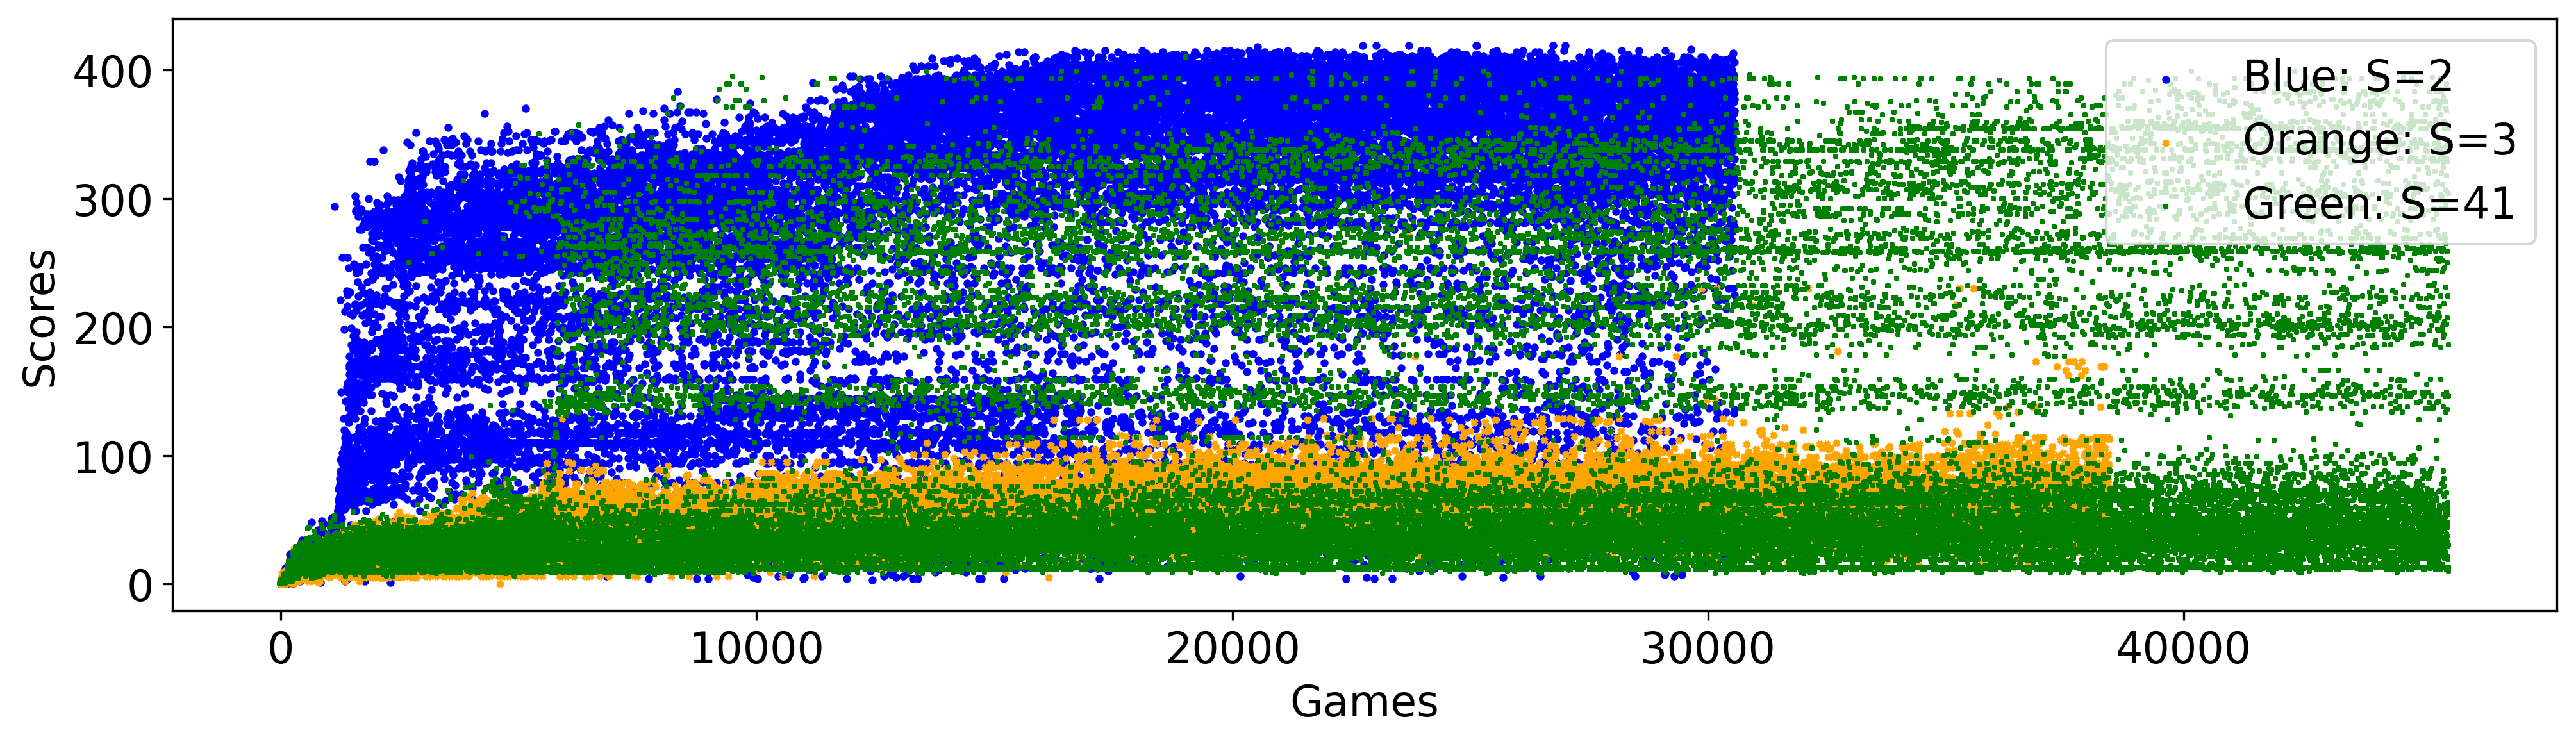

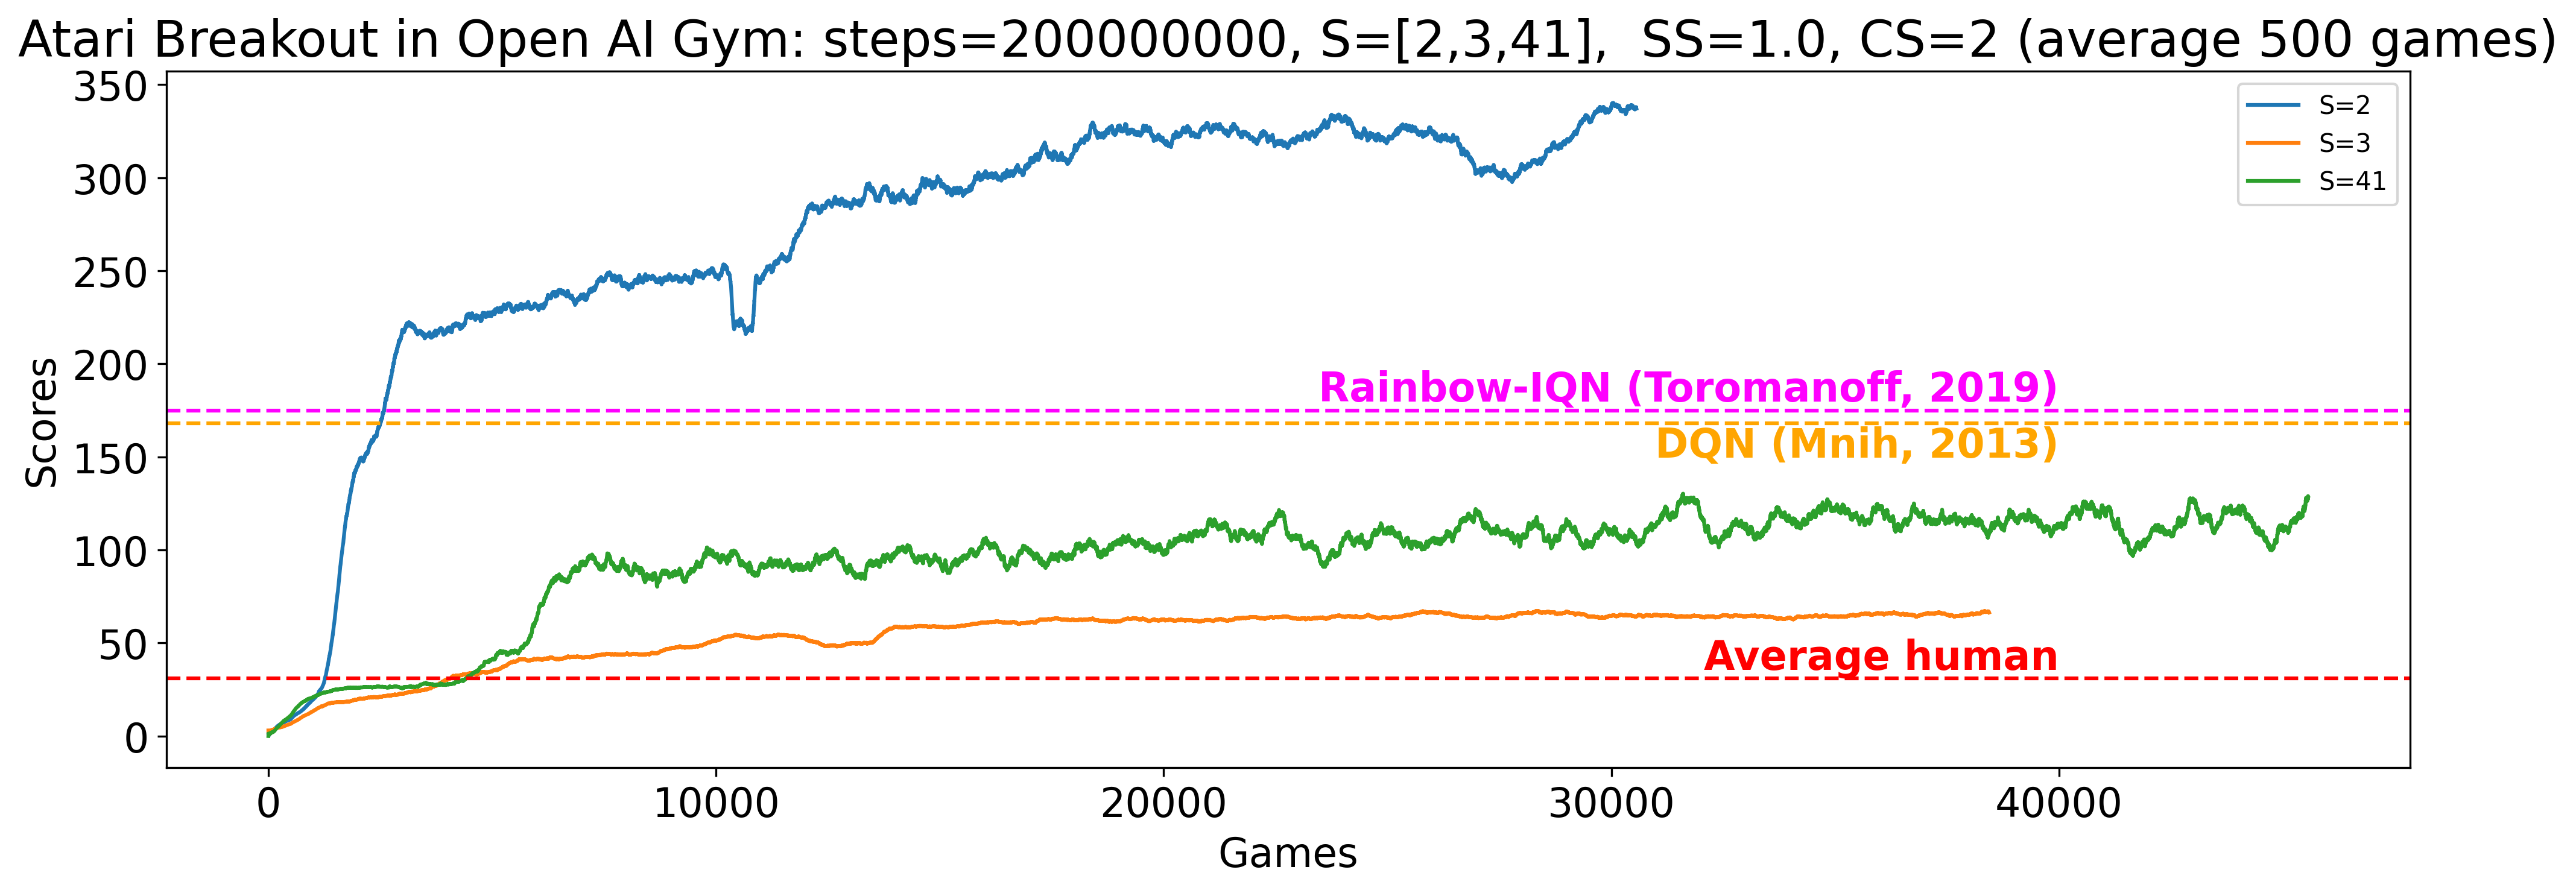

In [5]:
steps = 200000000
tit = f"Atari Breakout in Open AI Gym: steps={steps}, S=[2,3,41],  SS=1.0, CS=2 (average 500 games)"

sss = [exp200000000_s2ss10lm2sc2cs2tu0,exp200000000_s3ss10lm2sc2cs2tu0,exp200000000_s41ss10lm2sc2cs2tu0]

for s in sss:
    print(round(np.mean(s),2),round(np.mean(s[-500:]),2))
print()
print(round(np.mean([np.mean(s) for s in sss]),2),round(np.mean([np.mean(s[-500:]) for s in sss]),2))

#df = pd.DataFrame({f'S=2': pd.Series(sss[0]),f'S=3': pd.Series(sss[1]),f'S=41': pd.Series(sss[2])})
#p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["figure.dpi"] = 300
dottsize = 4
plt.scatter(np.arange(len(sss[0])),sss[0], label='Blue: S=2', color='blue', marker='o', s=dottsize)
plt.scatter(np.arange(len(sss[1])),sss[1], label='Orange: S=3', color='orange', marker='x', s=dottsize)
plt.scatter(np.arange(len(sss[2])),sss[2], label='Green: S=41', color='green', marker='+', s=dottsize)
plt.xticks(fontsize=16);plt.yticks(fontsize=16);plt.legend(fontsize=16)
plt.ylabel("Scores",fontsize=16);plt.xlabel("Games",fontsize=16);plt.show()

df = pd.DataFrame({f'S=2': pd.Series(sss[0]).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(sss[1]).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(sss[2]).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);

plt.axhline(y=31, color='r', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(40000, 36, f'Average human', color='red', fontweight='bold', ha='right', fontsize=16)

plt.axhline(y=175, color='magenta', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(40000, 180, 'Rainbow-IQN (Toromanoff, 2019)', color='magenta', fontweight='bold', ha='right', fontsize=16)

plt.axhline(y=168, color='orange', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(40000, 150, 'DQN (Mnih, 2013)', color='orange', fontweight='bold', ha='right', fontsize=16)

plt.ylabel("Scores",fontsize=16);plt.xlabel("Games",fontsize=16);plt.show()


48.62 69.59
82.74 112.04
96.23 134.08

75.86 105.24


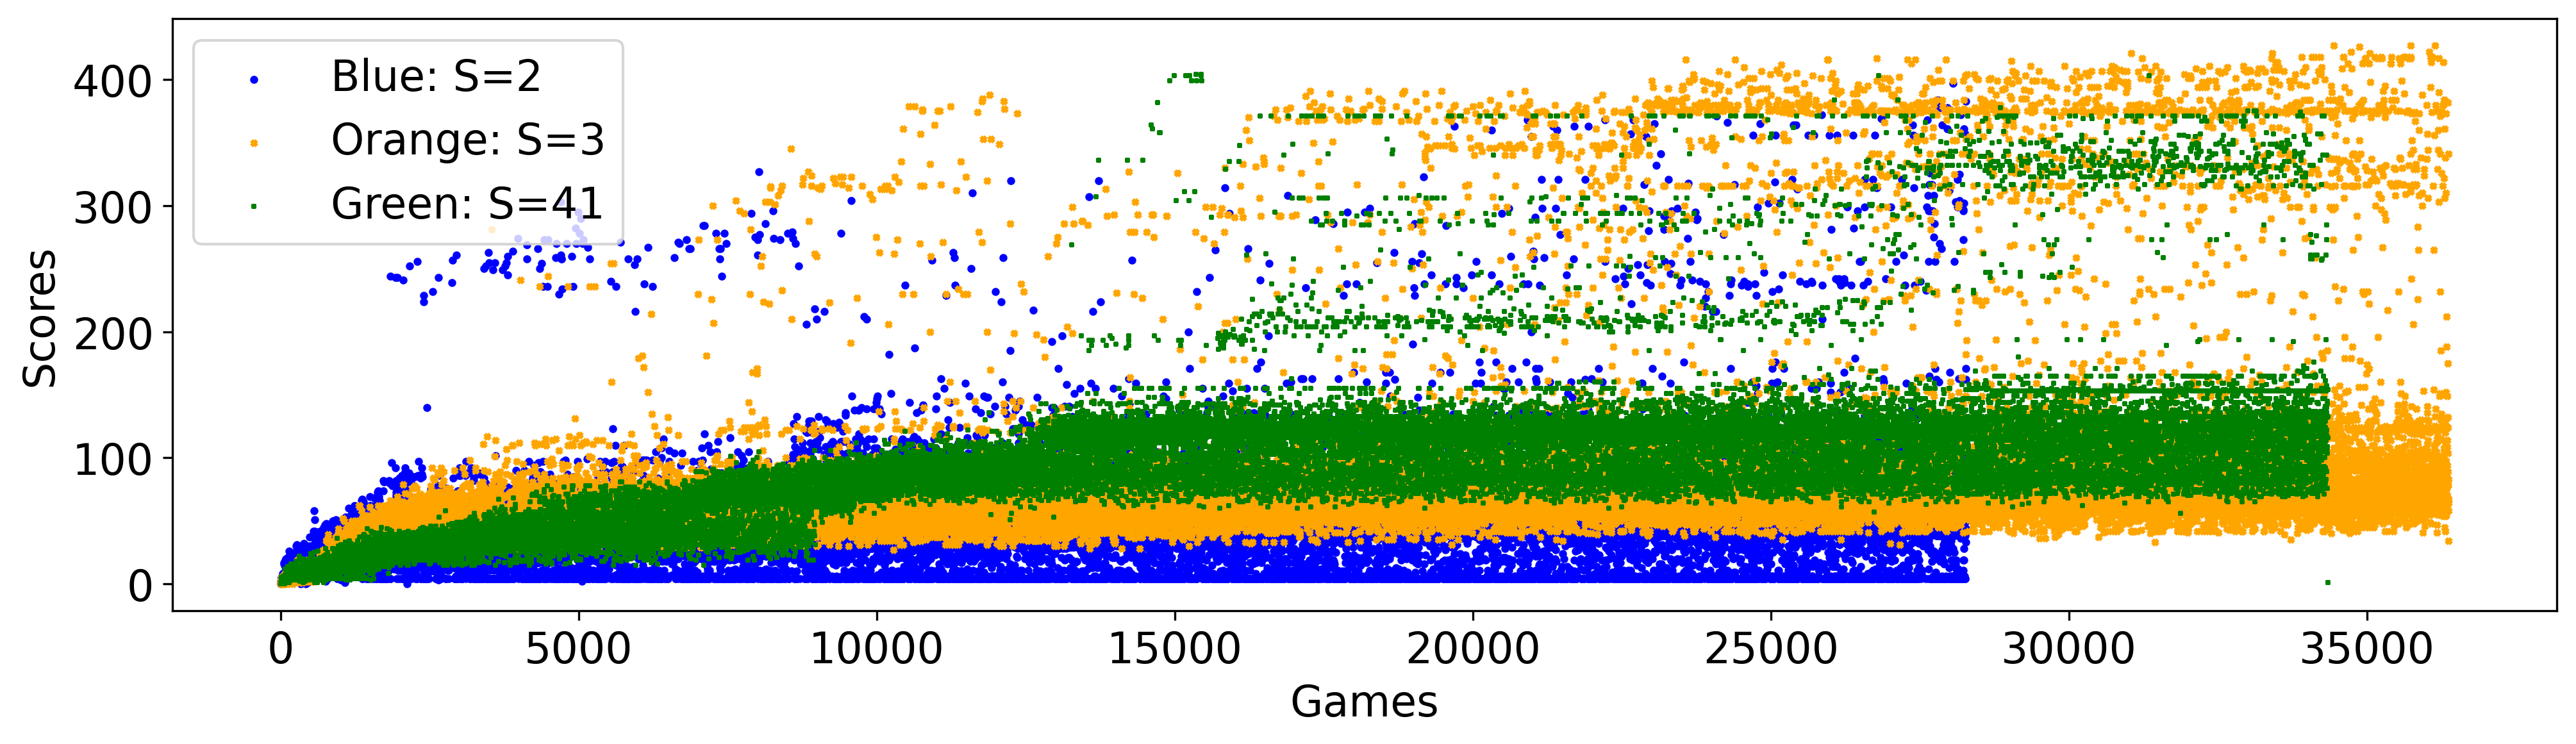

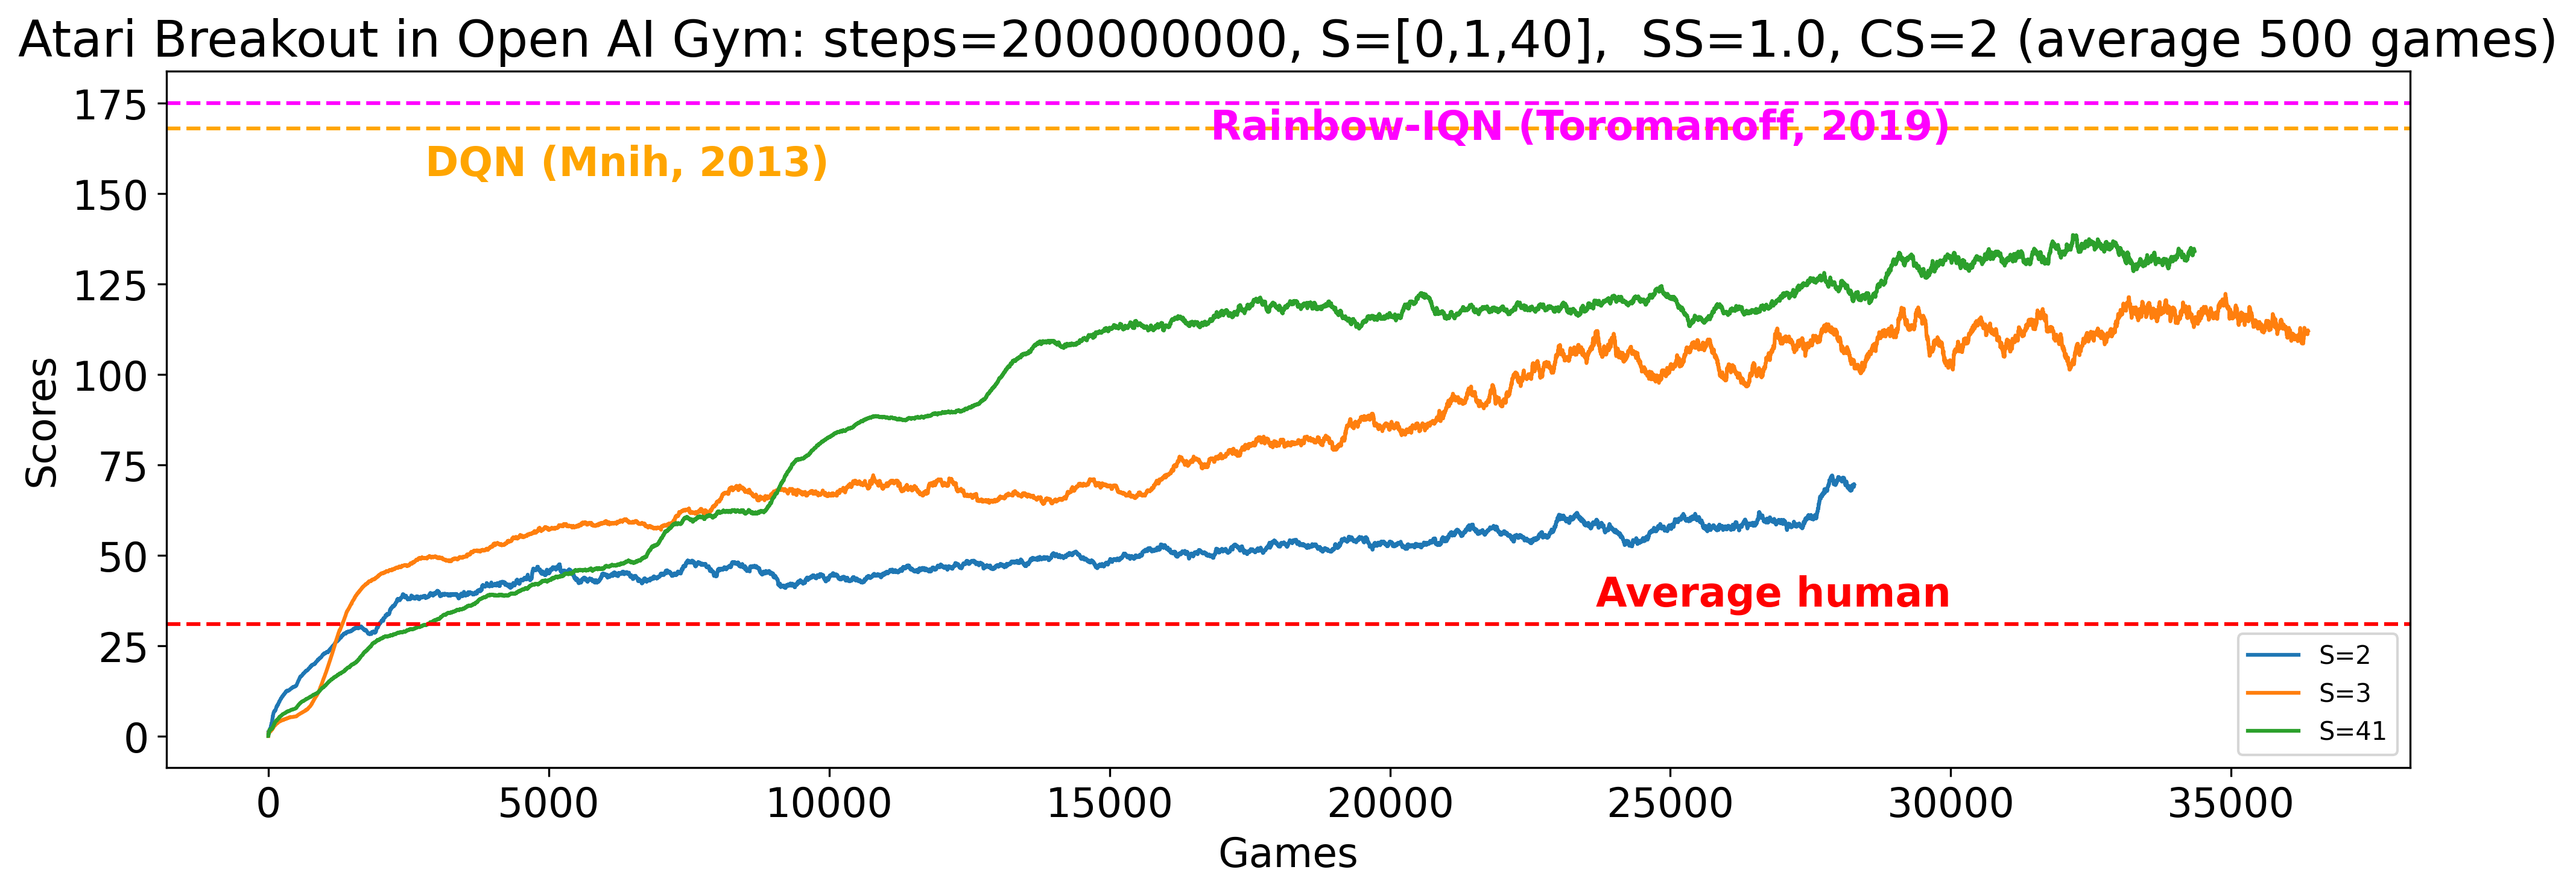

In [6]:
steps = 200000000
tit = f"Atari Breakout in Open AI Gym: steps={steps}, S=[0,1,40],  SS=1.0, CS=2 (average 500 games)"

sss = [exp200000000_s0ss10lm2sc2cs2tu0,exp200000000_s1ss10lm2sc2cs2tu0,exp200000000_s40ss10lm2sc2cs2tu0]

for s in sss:
    print(round(np.mean(s),2),round(np.mean(s[-500:]),2))
print()
print(round(np.mean([np.mean(s) for s in sss]),2),round(np.mean([np.mean(s[-500:]) for s in sss]),2))

#df = pd.DataFrame({f'S=2': pd.Series(sss[0]),f'S=3': pd.Series(sss[1]),f'S=41': pd.Series(sss[2])})
#p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["figure.dpi"] = 300
dottsize = 4
plt.scatter(np.arange(len(sss[0])),sss[0], label='Blue: S=2', color='blue', marker='o', s=dottsize)
plt.scatter(np.arange(len(sss[1])),sss[1], label='Orange: S=3', color='orange', marker='x', s=dottsize)
plt.scatter(np.arange(len(sss[2])),sss[2], label='Green: S=41', color='green', marker='+', s=dottsize)
plt.xticks(fontsize=16);plt.yticks(fontsize=16);plt.legend(fontsize=16)
plt.ylabel("Scores",fontsize=16);plt.xlabel("Games",fontsize=16);plt.show()

df = pd.DataFrame({f'S=2': pd.Series(sss[0]).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(sss[1]).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(sss[2]).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);

plt.axhline(y=31, color='r', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(30000, 36, f'Average human', color='red', fontweight='bold', ha='right', fontsize=16)
plt.axhline(y=175, color='magenta', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(30000, 165, f'Rainbow-IQN (Toromanoff, 2019)', color='magenta', fontweight='bold', ha='right', fontsize=16)
plt.axhline(y=168, color='orange', linestyle='--', linewidth=1.5, label=f'Average human')
plt.text(10000, 155, 'DQN (Mnih, 2013)', color='orange', fontweight='bold', ha='right', fontsize=16)

plt.ylabel("Scores",fontsize=16);plt.xlabel("Games",fontsize=16);plt.show()


In [7]:
#DOING S=2,3,41: CS=2 400m = 200M + 200M !!!

#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=2 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp400000000_s2ss10lm2sc2cs2tu0.txt -i=exp200000000_s2ss10lm2sc2cs2tu0 -o=exp400000000_s2ss10lm2sc2cs2tu0
#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=3 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp400000000_s3ss10lm2sc2cs2tu0.txt -i=exp200000000_s3ss10lm2sc2cs2tu0 -o=exp400000000_s3ss10lm2sc2cs2tu0
#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=41 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp400000000_s41ss10lm2sc2cs2tu0.txt -i=exp200000000_s41ss10lm2sc2cs2tu0 -o=exp400000000_s41ss10lm2sc2cs2tu0

#DOING - check the output - recovering removed file sim_test3/exp200000000_s2ss10lm2sc2cs2tu0.txt 
#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=2 -mg=5000000 -mt=200000000 -sm="exp(-d)" > sim_test3/exp200000000_s2ss10lm2sc2cs2tu0.txt

#TODO for 2,3,41: CS=3, 200M

#TODO for 0,1,40: CS=2 400m = 200M + 200M !!!

